# Deep Learning CA2 Part A
## GAN Experiments

**Notebook:** `02_GAN_Experiments.ipynb`  
**Primary owner:** Rudhresh  
**Dataset:** CIFAR-10  
**Framework:** TensorFlow and Keras  
**Environment:** Google Colab  

This notebook develops, evaluates, improves, and selects the GAN component of the project. It follows the shared data and preprocessing decisions established in Notebook 1.

## 1. Notebook Overview and EDA Linkage

### 1.1 Purpose and scope

This notebook investigates how suitable GAN architectures can learn the CIFAR-10 training distribution and generate plausible `32 × 32` RGB images. The work begins with a fair comparison of three foundations:

1. a serious Dense GAN,
2. a DCGAN, and
3. a WGAN-GP.

The strongest foundation is then improved through controlled experiments covering latent dimension, generator upsampling, network capacity, learning-rate balance and TTUR, and data augmentation. The accumulated unconditional configuration is confirmed across independent training seeds before the notebook investigates class conditioning, grayscale generation, a focused conditional augmentation ablation, and the final unconditional-versus-conditional comparison.

The selected GAN is then exported, fresh-reload verified and frozen for the later GAN-versus-VAE comparison.

The notebook must produce explicit evidence-based answers to the assignment questions:

- Did data augmentation improve GAN performance?
- Was grayscale generation easier or harder than RGB generation?
- Which CIFAR-10 classes were relatively easier or harder to generate, and why?
- How can the model generate an image from a requested class?

The official CIFAR-10 test set is not used for training, development evaluation, checkpoint selection, or model tuning in this notebook. Notebook 4 will perform the final held-out GAN-versus-VAE comparison, the memorisation audit, and the official 1,000-image generation after both model families have been frozen.

### Implementation principle

The notebook is designed for Google Colab runtimes that may disconnect. Model builders, model creation, optimiser setup, checkpoint restoration, training functions, training execution, history loading, and evaluation will remain in separate cells. Long-running experiments will save only the artifacts needed to continue safely:

- resumable checkpoints,
- generator and discriminator or critic weights,
- one training-history CSV per run,
- one master models-and-metrics CSV, and
- important image grids.

No experiment registry, configuration framework, JSON metadata bundle, fixed-input `.npy` files, or general-purpose persistence system will be created.

### 1.2 Notebook roadmap

| Stage | Sections | Purpose |
|---|---:|---|
| Foundation | 1 to 4 | Establish the project scope, GAN concepts, Colab workflow and evaluation methodology |
| Architecture screen | 5 | Compare Dense GAN, DCGAN and WGAN-GP under controlled conditions |
| Post-architecture safeguards | 6 | Establish reusable evaluation, persistence, calibration, coverage and restart utilities |
| Controlled unconditional improvements | 7 to 11 | Test latent dimension, generator upsampling, capacity, learning-rate balance and TTUR, and data augmentation |
| Final unconditional GAN | 12 | Confirm the accumulated unconditional configuration across independent training seeds |
| Main conditional GAN | 13 | Add class conditioning and evaluate requested-class generation |
| Grayscale experiment | 14 | Test whether reduced channel complexity changes structural generation quality |
| Focused conditional augmentation ablation | 15 | Test whether flip-and-translation augmentation remains useful after conditioning |
| Final GAN comparison | 16 | Compare the final unconditional and conditional GANs using the complete existing evidence |
| Freeze and handoff | 17 | Save, fresh-reload verify and freeze the selected GAN for Notebook 4 |

The notebook develops two serious final GAN candidates:

1. an improved unconditional GAN;
2. a conditional GAN that inherits the improved unconditional configuration and changes only what is required for class conditioning.

No winner is assumed beforehand. The final selection in Section 16 is based on the complete evidence available for both finalists.

### 1.3 EDA findings carried into GAN development

Notebook 1 completed the shared CIFAR-10 exploration and preprocessing decisions. The relevant findings are referenced here rather than repeated.

| EDA finding | GAN modelling or evaluation decision |
|---|---|
| CIFAR-10 contains substantial within-class variation | Evaluate diversity and repetition, not only visual sharpness |
| Some valid real images are blurry, cropped, or visually ambiguous | Use realistic Clear, Marginal, and Nonsense criteria rather than expecting perfect images |
| RGB information contributes useful colour and object cues | Retain three colour channels for the main GAN track |
| Images are only `32 × 32` pixels | Use compact architectures designed for low-resolution image generation |
| The ten classes are balanced | Do not apply class weighting, over-sampling, or under-sampling |
| Vehicle classes may contain more consistent large-scale geometry | Test whether vehicle classes are relatively easier to generate |
| Animal classes show greater pose, texture, and background variation | Test whether animal classes are relatively harder to generate |
| Visually related pairs may be confused, including cat/dog and automobile/truck | Examine conditional class-match errors and later compare them with the EDA hypotheses |
| Horizontal flips, small translations, and mild colour changes are plausible | Investigate augmentation experimentally rather than assuming it helps |
| Crop-resize transformations may remove useful low-resolution details | Do not use crop-resize as the default augmentation |
| The official test set is reserved for final evaluation | Use the training distribution only for development decisions in this notebook |

The later class-difficulty analysis will explicitly state whether the EDA hypotheses were confirmed, partly confirmed, or refuted by generated-image evidence.



---



## 2. GAN Background and Syllabus Concepts

This section introduces the GAN concepts required to understand the later architectures, training loops, experiments, and evaluation. It focuses on ideas that directly affect the implementation rather than presenting a broad literature review.

### 2.1 Generative Adversarial Networks framework

Generative Adversarial Networks were introduced by Goodfellow et al. in 2014. A GAN contains two neural networks trained in competition:

- the **generator**, which creates synthetic samples
- the **discriminator**, which evaluates whether samples appear real or generated

The generator receives a random latent vector $z$, sampled from a simple distribution such as a standard normal distribution. It transforms this vector into a generated image:

$$
\hat{x} = G(z)
$$

The latent vector does not directly represent pixels. Instead, it provides a compact source of variation from which the generator learns factors such as colour, shape, texture, viewpoint, and background.

For a standard GAN, the discriminator receives either a real training image $x$ or a generated image $\hat{x}$, and outputs a probability representing whether the input appears real:

$$
D(x) \in [0,1]
$$

The generator therefore learns indirectly. It is not given one correct target image for each latent vector. Instead, it improves by producing images that the discriminator increasingly struggles to distinguish from the real CIFAR-10 distribution.

This framework is suitable for CIFAR-10 because the task is to learn a distribution of plausible images rather than predict one fixed output for each input.

### 2.2 Real and generated streams: the double feedback loop

A GAN trains using two connected feedback processes.

```text
Random latent vector z
        |
        v
   Generator G
        |
        v
 Generated image ----------------------+
                                        |
Real CIFAR-10 image ----------------+   |
                                    |   |
                                    v   v
                              Discriminator D
                                    |
                          Real or generated score
```

The discriminator receives two streams:

1. real images sampled from the CIFAR-10 training set
2. generated images produced from random latent vectors

The discriminator receives direct supervision because the identities of the real and generated samples are known during training. Its parameters are updated to assign higher realness scores to real images and lower scores to generated images.

The generator forms the second feedback loop. Its generated images pass through the discriminator, and the resulting discriminator response provides the gradient used to update the generator. The generator therefore learns through the changing judgement of the discriminator rather than through direct image targets.

As training progresses, both networks change. The discriminator learns to identify weaknesses in generated images, while the generator learns to reduce those weaknesses.

### 2.3 Alternating static-adversary training

The generator and discriminator are updated in alternating steps. During each update, one network acts as a temporarily static adversary.

#### Discriminator update

1. Sample a batch of real images.
2. Sample latent vectors and generate fake images.
3. Do not update the generator.
4. Update the discriminator using both real and generated images.

#### Generator update

1. Sample a new batch of latent vectors.
2. Generate fake images.
3. Pass the generated images through the discriminator.
4. Do not optimise the discriminator's trainable variables.
5. Update only the generator so that its images receive more favourable discriminator responses.

Keeping one network static does not mean removing it from the forward pass. During the generator update, the discriminator must still process the generated images so that gradients can flow through the discriminator computation to the generator.

The exact training mode of layers such as Batch Normalisation must also be handled deliberately. This will be made explicit in the later implementation rather than left to hidden Keras behaviour.

This alternating static-adversary rule is a core implementation requirement. Incorrect handling can update the wrong network, create inconsistent normalisation behaviour, or make the adversarial comparison invalid.

The course material also presents discriminator pretraining as a possible way to give the generator a more informative early opponent. It is retained here only as a reserve option. It will not be used automatically because an excessively strong initial discriminator may also make early generator learning more difficult.

### 2.4 Generator upsampling and adversary downsampling

For image generation, the two networks generally perform opposite spatial operations.

#### Generator

The generator begins with a compact latent vector and progressively converts it into an image. A convolutional generator commonly:

1. projects the latent vector into a small spatial feature map
2. learns increasingly detailed feature representations
3. upsamples the feature maps
4. produces the required `32 × 32 × 3` RGB output

Possible upsampling approaches include transposed convolution and `UpSampling2D` followed by standard convolution. These will be compared later because they may produce different visual artifacts.

#### Discriminator

The discriminator follows the opposite direction. It receives an image and progressively reduces its spatial dimensions while learning increasingly abstract features:

```text
image
→ local edges and colours
→ textures and object parts
→ global realness judgement
```

Convolutional layers are suitable because they learn local spatial patterns using shared filters. This is more appropriate for images than immediately flattening all pixels and treating every spatial position independently.

A standard GAN discriminator normally ends with a sigmoid real or fake probability. A WGAN-GP instead uses a **critic**, which ends with an unrestricted real-valued score and no sigmoid output.

### 2.5 Adversarial balance and common failure modes

GAN training is difficult because the generator and adversary must improve at compatible rates. Their objectives are interdependent, and improvement by one network changes the learning problem faced by the other.

#### Adversary overpowering the generator

When the discriminator or critic becomes too effective relative to the generator:

- generated samples may be rejected easily
- the generator may receive weak or unhelpful learning signals
- visual improvement may stall
- diversity may decrease

#### Generator overpowering a weak adversary

When the adversary is too weak:

- unrealistic images may receive favourable scores
- the generator may exploit weaknesses in the adversary
- adversarial losses may appear favourable without corresponding visual quality

#### Mode collapse

Mode collapse occurs when different latent vectors produce very similar outputs. A collapsed model may generate a small set of plausible-looking images while failing to represent the diversity of CIFAR-10.

#### Oscillation and instability

Because both objectives change during training, image quality and losses may oscillate rather than improve smoothly. A later epoch is therefore not automatically better than an earlier checkpoint.

The later experiments investigate several controls that can affect adversarial balance, stability and generated-image quality:

- generator and discriminator learning-rate balance;
- two time-scale update rules;
- targeted generator and discriminator capacity changes;
- generator upsampling design;
- discriminator-side data augmentation;
- independent training-seed confirmation;
- gradient penalty through the WGAN-GP architecture-screen alternative.

Broad update-ratio, batch-size, standalone-normalisation and stabilisation sweeps may or may not be performed, depending on later evidence.

### 2.6 GAN foundations investigated in this notebook

The architecture screen compares three GAN formulations. Each provides a meaningful foundation rather than serving as an intentionally weak model.

| Foundation | Generator and adversary | Spatial treatment | Training objective | Main purpose in this notebook |
|---|---|---|---|---|
| Dense GAN | Dense generator and dense discriminator | Images are flattened, so explicit spatial structure is not preserved | Binary cross-entropy adversarial objective | Establish a serious non-convolutional reference and test the value of spatial modelling |
| DCGAN | Convolutional generator and discriminator | The generator upsamples feature maps while the discriminator downsamples images | Binary cross-entropy adversarial objective | Test whether convolutional feature learning substantially improves CIFAR-10 generation |
| WGAN-GP | Convolutional generator and critic | Convolutional spatial processing with unrestricted critic scores | Wasserstein objective with gradient penalty | Test a more advanced formulation designed to provide more stable and informative adversarial learning |

The WGAN-GP critic replaces the standard discriminator. It does not output a probability and does not use a sigmoid final activation. Its gradient penalty encourages the critic to satisfy the smoothness constraint required by the Wasserstein formulation.

WGAN-GP is treated as an above-syllabus extension. It is implemented directly, trained only on CIFAR-10, and compared against simpler models rather than assumed to be superior.

No architecture winner is predicted in this section. Selection will be made only after all three models have completed their controlled architecture-screen runs.

### 2.7 Evaluating generated images

Generative modelling does not provide one classification-style metric that fully describes performance. A model may produce sharp images with low diversity, diverse images with weak recognisability, or favourable losses without convincing visual outputs.

The GANs will therefore be selected using multiple forms of evidence.

#### Visual evidence

- fixed-latent grids show how the same latent inputs change across checkpoints
- uncurated grids reduce cherry-picking risk
- manual Clear, Marginal and Nonsense scoring measures plausible image structure
- conditional evaluation separately measures whether the requested class is recognisable

#### Distribution and diversity evidence

- development FID compares generated and real feature distributions
- feature-space diversity evaluates variation between generated images
- near-duplicate checks identify excessive repetition
- progression grids and score behaviour help diagnose mode collapse

#### Stability and practical evidence

- generator and adversary losses are used as diagnostics
- real and fake adversary scores help assess balance
- repeated seeds test whether improvements are reproducible
- training time and parameter counts measure computational cost

Topic 5 also introduces KL divergence as a possible distribution-comparison method. KL divergence is not used here as a standalone image-realism score because raw image distributions are high dimensional and difficult to estimate reliably. It may be used only as supplementary evidence for selected low-level descriptor distributions when it answers a specific question.

FID is also interpreted cautiously. It uses features from an Inception network trained on ImageNet, while CIFAR-10 contains low-resolution `32 × 32` images that must be resized. FID is therefore treated as a consistent **relative comparator** between candidates evaluated through the same pipeline, not as an absolute measure of realism, recognisability, diversity, or originality.

The final generated-to-training nearest-neighbour memorisation audit is deferred to Notebook 4, where it will be applied only to the frozen GAN and VAE finalists.

### 2.8 Broader applications and ethical context

GANs have been extended beyond small image generation.

- **StyleGAN** demonstrates high-resolution and controllable image synthesis.
- **pix2pix** applies conditional adversarial learning to paired image-to-image translation.
- **SRGAN** applies adversarial learning to image super-resolution.
- Related techniques can create synthetic audio, video, faces, and other media.

These applications demonstrate the flexibility of adversarial learning, but they solve different or substantially more complex tasks than the present `32 × 32` CIFAR-10 problem. They are discussed for context and are not trained in this notebook.

The same ability to create plausible synthetic media can also be misused for impersonation, misinformation, manipulation, and non-consensual content commonly associated with deepfakes. Responsible use requires disclosure, careful evaluation, and awareness of who may be affected by generated media.

This project uses a small public educational dataset and does not attempt photorealistic human generation or identity imitation.



---



## 3. Colab Environment, CIFAR-10 and Simple Restart Setup

This section establishes the shared environment used by all later GAN experiments.

Google Colab runtime memory is temporary. Persistent project artifacts are stored in Google Drive under the root `Colab Notebooks` directory, which also contains the four project notebooks.

Only the following subdirectories are used:

```text
Colab Notebooks/
├── checkpoints/
├── weights/
├── histories/
└── grids/
```

The local Colab runtime may be disconnected or replaced without losing completed training evidence. After a restart, the notebook can rebuild the relevant architecture from code and load checkpoints or weights from Drive.

The project uses standard `float32` computation. Mixed precision and XLA are not enabled because the available L4 GPU is sufficient for the planned CIFAR-10 models, while standard precision keeps adversarial training and WGAN-GP gradient-penalty calculations easier to inspect and debug.

In [1]:
import os
from pathlib import Path


# The project notebooks and all persistent folders are stored here.
ROOT_DIR = Path("[local project directory]")

# Reuse the CIFAR-10 dataset already stored in Google Drive.
KERAS_HOME_DIR = ROOT_DIR / ".keras"
os.environ["KERAS_HOME"] = str(KERAS_HOME_DIR)

ROOT_DIR.mkdir(parents=True, exist_ok=True)
KERAS_HOME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT_DIR}")
print(f"Keras cache:  {KERAS_HOME_DIR}")

Mounted at /content/drive
Project root: [local project directory]
Keras cache:  [local project directory]/.keras


In [2]:
import gc
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

import tensorflow as tf
import keras

from keras import layers
from keras import losses
from keras import metrics
from keras import optimizers
from keras import initializers
from keras import regularizers

from keras.applications import InceptionV3
from keras.applications.inception_v3 import preprocess_input

from scipy.linalg import sqrtm
from tqdm.auto import tqdm

from scipy.spatial.distance import pdist, squareform
import re
import shutil
from PIL import Image

In [3]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    normalized_mutual_info_score,
)

In [4]:
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"Default float type: {keras.backend.floatx()}")

gpus = tf.config.list_physical_devices("GPU")

print(f"Visible GPU count:  {len(gpus)}")

if gpus:
    print(f"GPU device:         {gpus[0]}")
else:
    raise RuntimeError(
        "No GPU was detected. In Colab, select Runtime > Change runtime type "
        "> Hardware accelerator > L4 GPU before training."
    )

precision_policy = keras.mixed_precision.global_policy()
print(f"Precision policy:   {precision_policy.name}")

assert keras.backend.floatx() == "float32"
assert precision_policy.name == "float32"

print("\nEnvironment check passed. Standard float32 training is active.")

TensorFlow version: 2.20.0
Keras version:      3.13.2
Default float type: float32
Visible GPU count:  1
GPU device:         PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Precision policy:   float32

Environment check passed. Standard float32 training is active.


In [5]:
PRIMARY_SEED = 42
SECONDARY_SEED = 123
THIRD_SEED = 456
FIXED_LATENT_SEED = 999

random.seed(PRIMARY_SEED)
np.random.seed(PRIMARY_SEED)
tf.random.set_seed(PRIMARY_SEED)

print("Shared seeds")
print(f"Primary seed:       {PRIMARY_SEED}")
print(f"Secondary seed:     {SECONDARY_SEED}")
print(f"Third seed:         {THIRD_SEED}")
print(f"Fixed latent seed:  {FIXED_LATENT_SEED}")

Shared seeds
Primary seed:       42
Secondary seed:     123
Third seed:         456
Fixed latent seed:  999


In [6]:
CHECKPOINTS_DIR = ROOT_DIR / "checkpoints"
WEIGHTS_DIR = ROOT_DIR / "weights"
HISTORIES_DIR = ROOT_DIR / "histories"
GRIDS_DIR = ROOT_DIR / "grids"

CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
HISTORIES_DIR.mkdir(parents=True, exist_ok=True)
GRIDS_DIR.mkdir(parents=True, exist_ok=True)

print("Persistent directories")
print(f"Checkpoints: {CHECKPOINTS_DIR}")
print(f"Weights:     {WEIGHTS_DIR}")
print(f"Histories:   {HISTORIES_DIR}")
print(f"Grids:       {GRIDS_DIR}")

Persistent directories
Checkpoints: [local project directory]/checkpoints
Weights:     [local project directory]/weights
Histories:   [local project directory]/histories
Grids:       [local project directory]/grids


### 3.2 CIFAR-10 loading and GAN preprocessing

The official CIFAR-10 loader provided in the assignment brief is used. The dataset is read from the Keras cache stored in Google Drive.

All 50,000 official training images are used for GAN development. The 10,000 official test images are loaded only because they are returned by the dataset API. They remain unprocessed and unused for training, checkpoint selection, development FID, or tuning in this notebook.

For GAN training, RGB pixel values are converted from unsigned integers in `[0, 255]` to `float32` values in `[-1, 1]`. This range matches the generator's later `tanh` output activation.

In [7]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = (
    tf.keras.datasets.cifar10.load_data()
)

print("CIFAR-10 loaded successfully.")
print(f"Training images: {x_train_raw.shape}")
print(f"Training labels: {y_train_raw.shape}")
print(f"Test images:     {x_test_raw.shape}")
print(f"Test labels:     {y_test_raw.shape}")

CIFAR-10 loaded successfully.
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images:     (10000, 32, 32, 3)
Test labels:     (10000, 1)


In [8]:
CLASS_NAMES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SHAPE = (32, 32, 3)

# Flatten labels from shape (n, 1) to shape (n,).
y_train = y_train_raw.reshape(-1).astype(np.int64)
y_test = y_test_raw.reshape(-1).astype(np.int64)

# Scale training images from uint8 [0, 255] to float32 [-1, 1].
x_train_gan = (
    x_train_raw.astype(np.float32) - 127.5
) / 127.5

print(f"x_train_gan shape: {x_train_gan.shape}")
print(f"x_train_gan dtype: {x_train_gan.dtype}")
print(
    "x_train_gan range: "
    f"[{x_train_gan.min():.3f}, {x_train_gan.max():.3f}]"
)

x_train_gan shape: (50000, 32, 32, 3)
x_train_gan dtype: float32
x_train_gan range: [-1.000, 1.000]


In [9]:
assert x_train_raw.shape == (50_000, 32, 32, 3)
assert y_train_raw.shape == (50_000, 1)

assert x_test_raw.shape == (10_000, 32, 32, 3)
assert y_test_raw.shape == (10_000, 1)

assert x_train_raw.dtype == np.uint8
assert x_test_raw.dtype == np.uint8

assert x_train_gan.shape == (50_000, 32, 32, 3)
assert x_train_gan.dtype == np.float32

assert np.isclose(x_train_gan.min(), -1.0)
assert np.isclose(x_train_gan.max(), 1.0)

assert y_train.shape == (50_000,)
assert y_test.shape == (10_000,)

assert set(np.unique(y_train)) == set(range(NUM_CLASSES))
assert set(np.unique(y_test)) == set(range(NUM_CLASSES))

print("Dataset validation passed.")
print("Main GAN training data: 50,000 RGB training images")
print("Training range:          [-1, 1]")
print("Official test set:       loaded but protected and unused")

Dataset validation passed.
Main GAN training data: 50,000 RGB training images
Training range:          [-1, 1]
Official test set:       loaded but protected and unused


### 3.3 Reusable training input pipeline

Every experiment uses a fresh `tf.data.Dataset` created from the selected training images and batch size.

The pipeline:

1. shuffles the training images using the experiment seed
2. creates batches without discarding the final incomplete batch
3. prefetches batches while the GPU processes the current batch

Keeping the final batch ensures that all 50,000 training images remain available during each epoch. Later training functions must therefore obtain the current batch size dynamically rather than assuming that every batch contains the configured batch size.

In [10]:
# Create a shuffled and prefetched image-only training dataset.
def make_training_dataset(images, batch_size, seed):
    dataset = tf.data.Dataset.from_tensor_slices(images)

    dataset = dataset.shuffle(
        buffer_size=len(images),
        seed=seed,
        reshuffle_each_iteration=True,
    )

    dataset = dataset.batch(
        batch_size,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

### 3.4 Reproducible latent inputs

GAN training uses newly sampled random latent vectors. Evaluation also requires fixed latent inputs so that visual changes across checkpoints reflect model development rather than different random samples.

Fixed inputs are recreated from documented stateless seeds. They therefore remain identical after a Colab runtime restart without requiring saved `.npy` files.

In [11]:
# Create reproducible standard-normal latent vectors.
def make_stateless_noise(sample_count, latent_dim, seed):
    return tf.random.stateless_normal(
        shape=(sample_count, latent_dim),
        seed=[seed, 0],
        dtype=tf.float32,
    )

In [12]:
TEMP_BATCH_SIZE = 64
TEMP_LATENT_DIM = 100

temporary_dataset = make_training_dataset(
    images=x_train_gan,
    batch_size=TEMP_BATCH_SIZE,
    seed=PRIMARY_SEED,
)

temporary_batch = next(iter(temporary_dataset))

fixed_noise_a = make_stateless_noise(
    sample_count=16,
    latent_dim=TEMP_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

fixed_noise_b = make_stateless_noise(
    sample_count=16,
    latent_dim=TEMP_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

print("Temporary image batch")
print(f"Shape: {temporary_batch.shape}")
print(f"Dtype: {temporary_batch.dtype}")
print(
    "Range: "
    f"[{tf.reduce_min(temporary_batch).numpy():.3f}, "
    f"{tf.reduce_max(temporary_batch).numpy():.3f}]"
)

print("\nFixed latent vectors")
print(f"Shape: {fixed_noise_a.shape}")
print(f"Dtype: {fixed_noise_a.dtype}")
print(
    "Exactly reproducible: "
    f"{np.array_equal(fixed_noise_a.numpy(), fixed_noise_b.numpy())}"
)

assert temporary_batch.shape == (TEMP_BATCH_SIZE, 32, 32, 3)
assert temporary_batch.dtype == tf.float32
assert fixed_noise_a.shape == (16, TEMP_LATENT_DIM)
assert np.array_equal(fixed_noise_a.numpy(), fixed_noise_b.numpy())

del temporary_dataset
del temporary_batch
del fixed_noise_a
del fixed_noise_b

print("\nSection 3 validation passed.")

Temporary image batch
Shape: (64, 32, 32, 3)
Dtype: <dtype: 'float32'>
Range: [-1.000, 1.000]

Fixed latent vectors
Shape: (16, 100)
Dtype: <dtype: 'float32'>
Exactly reproducible: True

Section 3 validation passed.


### 3.5 Persistence and runtime recovery contract

Google Colab runtime memory is treated as temporary. No completed experiment may depend on its original in-memory model objects remaining available.

Each formal training run saves the minimum artifacts required to resume training, reconstruct results, and complete evaluation after a fresh runtime.

#### Saved after every completed epoch

Each run updates one history CSV containing:

- epoch number
- generator loss
- discriminator or critic loss
- mean real score
- mean generated score
- gradient penalty for WGAN-GP
- epoch training time

The history CSV is updated after every completed epoch.

#### Saved every 10 epochs and at the final epoch

Each run saves:

- a full resumable TensorFlow checkpoint
- a fixed-seed progression grid

The full checkpoint contains:

- generator
- discriminator or critic
- both optimisers
- completed epoch counter

The checkpoint epoch is the source of truth for the recoverable model state.

#### Saved at formal evaluation milestones

For architecture-screen and shortlisted formal runs, generator weights are saved at:

```text
epoch 50
epoch 70
epoch 90
epoch 100
```

These weights allow later FID, manual scoring, diversity analysis, near-duplicate checks, mode-collapse analysis, and additional uncurated grids to be produced without retraining.

Minor exploratory runs do not automatically save every milestone weight. They normally retain only the final or selected generator unless earlier-checkpoint comparison is required.

#### Intentional runtime shutdown

Before deliberately ending or resetting a Colab runtime, a small manual save cell will write:

- the current full checkpoint
- the latest history CSV
- a current fixed-seed grid

#### Recovery after an interrupted training run

```text
Mount Google Drive
→ rerun imports and shared setup
→ reload and preprocess CIFAR-10
→ rerun the relevant model builders
→ recreate the same models and optimisers
→ recreate the checkpoint object
→ restore the latest checkpoint
→ align the history CSV to the restored epoch
→ resume from the next epoch
```

If the history CSV contains rows beyond the restored checkpoint epoch, those later rows are trimmed or ignored before training resumes.

#### Evaluation after completed training

```text
Mount Google Drive
→ rerun imports and shared setup
→ reload and preprocess CIFAR-10
→ rebuild the required generator architecture
→ load milestone or selected generator weights
→ recreate evaluation inputs using documented stateless seeds
→ run the required evaluation package
```

Completed experiments are evaluated by loading saved weights, not by retraining.

The notebook therefore remains modular across Colab sessions while avoiding a large experiment-management framework.

In [13]:
# CSV schemas and master results file
STANDARD_GAN_HISTORY_COLUMNS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

WGAN_GP_HISTORY_COLUMNS = [
    "epoch",
    "generator_loss",
    "critic_loss",
    "real_score",
    "fake_score",
    "gradient_penalty",
    "epoch_time_seconds",
]

MODELS_METRICS_COLUMNS = [
    "run_id",
    "experiment_family",
    "model",
    "main_change",
    "seed",
    "epochs_completed",
    "selected_epoch",
    "latent_dim",
    "batch_size",
    "generator_parameters",
    "adversary_parameters",
    "development_fid",
    "fid_std",
    "clear_count",
    "marginal_count",
    "nonsense_count",
    "diversity_summary",
    "training_time_minutes",
    "selected",
    "decision",
]

MODELS_METRICS_PATH = HISTORIES_DIR / "models_metrics.csv"

if not MODELS_METRICS_PATH.exists():
    pd.DataFrame(
        columns=MODELS_METRICS_COLUMNS
    ).to_csv(
        MODELS_METRICS_PATH,
        index=False,
    )

print(f"Master metrics CSV: {MODELS_METRICS_PATH}")

Master metrics CSV: [local project directory]/histories/models_metrics.csv


In [14]:
# Load one run's history CSV.
# When restored_epoch is provided, rows after the restored
# checkpoint epoch are removed because the checkpoint is the
# source of truth for recoverable model state.

def load_and_align_history(
    history_path,
    columns,
    restored_epoch=None,
):
    history_path = Path(history_path)
    history_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if history_path.exists():
        history = pd.read_csv(history_path)

        missing_columns = [
            column
            for column in columns
            if column not in history.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Missing history columns in "
                f"{history_path.name}: "
                f"{missing_columns}"
            )

        history = history[columns].copy()

    else:
        history = pd.DataFrame(
            columns=columns
        )

    if not history.empty:
        history["epoch"] = pd.to_numeric(
            history["epoch"],
            errors="raise",
        ).astype(int)

        history = (
            history
            .drop_duplicates(
                subset="epoch",
                keep="last",
            )
            .sort_values("epoch")
            .reset_index(drop=True)
        )

    if restored_epoch is not None:
        restored_epoch = int(restored_epoch)

        history = (
            history.loc[
                history["epoch"]
                <= restored_epoch
            ]
            .reset_index(drop=True)
        )

        history.to_csv(
            history_path,
            index=False,
        )

    return history

# Save one completed epoch.
# If the same epoch already exists, the newer row replaces it.
# This prevents duplicate epochs after a resumed run.
def save_epoch_history(
    history_path,
    row,
    columns,
):
    history_path = Path(history_path)

    missing_values = [
        column
        for column in columns
        if column not in row
    ]

    if missing_values:
        raise ValueError(
            f"Missing history values: "
            f"{missing_values}"
        )

    history = load_and_align_history(
        history_path=history_path,
        columns=columns,
    )

    row_df = pd.DataFrame([
        {
            column: row[column]
            for column in columns
        }
    ])

    if history.empty:
        history = row_df

    else:
        history = pd.concat(
            [history, row_df],
            ignore_index=True,
        )

    history["epoch"] = pd.to_numeric(
        history["epoch"],
        errors="raise",
    ).astype(int)

    history = (
        history
        .drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    history.to_csv(
        history_path,
        index=False,
    )

    return history

In [15]:
# Create or update one run in models_metrics.csv.
# Existing values are preserved when a later update provides
# only some of the results fields.
def update_models_metrics(result):
    if (
        "run_id" not in result
        or not str(result["run_id"]).strip()
    ):
        raise ValueError(
            "result must include a non-empty run_id"
        )

    if MODELS_METRICS_PATH.exists():
        metrics_df = pd.read_csv(
            MODELS_METRICS_PATH
        )

    else:
        metrics_df = pd.DataFrame(
            columns=MODELS_METRICS_COLUMNS
        )

    for column in MODELS_METRICS_COLUMNS:
        if column not in metrics_df.columns:
            metrics_df[column] = pd.NA

    metrics_df = metrics_df[
        MODELS_METRICS_COLUMNS
    ].copy()

    run_id = str(result["run_id"])
    existing_values = {}

    if not metrics_df.empty:
        matching_rows = metrics_df.loc[
            metrics_df["run_id"].astype(str)
            == run_id
        ]

        if not matching_rows.empty:
            existing_values = (
                matching_rows
                .iloc[-1]
                .to_dict()
            )

        metrics_df = metrics_df.loc[
            metrics_df["run_id"].astype(str)
            != run_id
        ]

    updated_row = {
        column: result.get(
            column,
            existing_values.get(
                column,
                pd.NA,
            ),
        )
        for column in MODELS_METRICS_COLUMNS
    }

    updated_row["run_id"] = run_id

    updated_row_df = pd.DataFrame(
        [updated_row]
    )

    if metrics_df.empty:
        metrics_df = updated_row_df

    else:
        metrics_df = pd.concat(
            [
                metrics_df,
                updated_row_df,
            ],
            ignore_index=True,
        )

    metrics_df.to_csv(
        MODELS_METRICS_PATH,
        index=False,
    )

    return metrics_df

In [16]:
TEST_HISTORY_PATH = Path(
    "/content/section3_history_test.csv"
)

TEST_METRICS_PATH = Path(
    "/content/section3_metrics_test.csv"
)

# Remove old temporary validation files.
TEST_HISTORY_PATH.unlink(
    missing_ok=True
)

TEST_METRICS_PATH.unlink(
    missing_ok=True
)

# Test epoch saving.
test_history = save_epoch_history(
    history_path=TEST_HISTORY_PATH,
    row={
        "epoch": 1,
        "generator_loss": 1.25,
        "discriminator_loss": 0.72,
        "real_score": 0.68,
        "fake_score": 0.31,
        "epoch_time_seconds": 4.5,
    },
    columns=STANDARD_GAN_HISTORY_COLUMNS,
)

test_history = save_epoch_history(
    history_path=TEST_HISTORY_PATH,
    row={
        "epoch": 2,
        "generator_loss": 1.18,
        "discriminator_loss": 0.69,
        "real_score": 0.71,
        "fake_score": 0.29,
        "epoch_time_seconds": 4.4,
    },
    columns=STANDARD_GAN_HISTORY_COLUMNS,
)

assert list(test_history["epoch"]) == [1, 2]

# Simulate restoring a checkpoint from epoch 1.
aligned_history = load_and_align_history(
    history_path=TEST_HISTORY_PATH,
    columns=STANDARD_GAN_HISTORY_COLUMNS,
    restored_epoch=1,
)

assert list(aligned_history["epoch"]) == [1]

# Test master-metrics update logic without touching
# the real project master CSV.
original_metrics_path = MODELS_METRICS_PATH
MODELS_METRICS_PATH = TEST_METRICS_PATH

test_metrics = update_models_metrics({
    "run_id": "TEST_RUN",
    "model": "Test GAN",
    "epochs_completed": 10,
})

test_metrics = update_models_metrics({
    "run_id": "TEST_RUN",
    "development_fid": 123.45,
    "decision": "Validation only",
})

test_row = test_metrics.loc[
    test_metrics["run_id"]
    == "TEST_RUN"
].iloc[0]

assert test_row["model"] == "Test GAN"
assert test_row["epochs_completed"] == 10
assert np.isclose(
    test_row["development_fid"],
    123.45,
)

# Restore the real project path.
MODELS_METRICS_PATH = original_metrics_path

# Remove temporary validation files.
TEST_HISTORY_PATH.unlink(
    missing_ok=True
)

TEST_METRICS_PATH.unlink(
    missing_ok=True
)

print("History CSV save passed.")
print("Checkpoint-history alignment passed.")
print("Master metrics update passed.")
print("Section 3.5 validation passed.")

History CSV save passed.
Checkpoint-history alignment passed.
Master metrics update passed.
Section 3.5 validation passed.


---

## 4. Evaluation Approach and Model-Selection Criteria

GANs are trained using adversarial objectives, but their losses do not directly measure whether generated images are plausible, recognisable, diverse, or free from repetition.

Every formal model decision in this notebook therefore uses multiple forms of evidence:

- training diagnostics
- fixed-seed progression grids
- uncurated generated-image grids
- structured manual scoring
- development FID
- diversity and repetition analysis
- training stability
- parameter count
- training time
- reproducibility across seeds

No architecture, checkpoint, or improvement is selected from loss alone, FID alone, or one visually appealing grid.

### 4.1 Development data and test-set boundary

All GANs in this notebook are trained using the 50,000 official CIFAR-10 training images.

The same 50,000-image training distribution is used as the real reference for development FID. This provides a consistent reference for comparing architectures, checkpoints, and improvements during model development.

The official 10,000-image test set is not used for:

- training
- augmentation
- preprocessing decisions
- checkpoint selection
- development FID
- manual scoring
- diversity analysis
- hyperparameter tuning
- architecture selection

The test arrays may remain in memory because they are returned by the official Keras loader, but they are not accessed after the initial dataset summary.

The official test set is first used in Notebook 4, after the final GAN and VAE models, checkpoints, and evaluation protocol have been frozen. No model tuning will occur after that final held-out evaluation.

### 4.2 Training diagnostics

Training diagnostics are used to understand adversarial balance and detect instability. They are not treated as direct image-quality metrics.

#### Dense GAN and DCGAN

The following values are recorded after every epoch:

- generator loss
- discriminator loss
- mean discriminator score for real images
- mean discriminator score for generated images
- epoch training time

#### WGAN-GP

The following values are recorded after every epoch:

- generator loss
- critic loss
- mean critic score for real images
- mean critic score for generated images
- gradient-penalty value
- epoch training time

The meaning and numerical scale of these values differ between standard GANs and WGAN-GP. Loss values are therefore interpreted within the relevant formulation rather than compared directly across model families.

The diagnostics are used to identify:

- persistent generator or adversary dominance
- oscillation
- stalled learning
- non-finite values
- sudden collapse
- late deterioration
- unstable gradient-penalty behaviour

Additional diagnostics such as gradient norms or activation distributions will be added only when a specific technical problem requires them.

### 4.3 Fixed-seed and uncurated image grids

Two types of generated-image grids are used.

#### Fixed-seed progression grids

The same stateless latent vectors are recreated at every saved checkpoint. A fixed grid is saved every 10 epochs.

Because the latent inputs remain unchanged, visual differences between these grids reflect changes in the generator rather than different random samples.

The progression grids are examined for:

- emergence of object-like structure
- colour development
- increasing or decreasing variety
- repeated outputs
- visual artifacts
- mode collapse
- late deterioration

#### Uncurated grids

At an evaluated checkpoint, a separate random sample is generated using a documented seed. Images are displayed without filtering, replacement, or manual selection.

Uncurated grids reduce cherry-picking and provide a more realistic view of typical generator output.

Fixed-seed grids support longitudinal comparison. Uncurated grids support quality and diversity evaluation. Neither is sufficient by itself.

### 4.4 Manual Clear, Marginal and Nonsense scoring

Manual evaluation uses 100 uncurated generated images produced with a documented seed.

Each image is assigned to one of three categories.

#### Clear

The image contains recognisable object-like structure with plausible overall organisation and meaningful CIFAR-10 class cues.

#### Marginal

The image contains plausible features but remains blurry, distorted, incomplete, background-dominated, or difficult to identify confidently.

CIFAR-10 contains valid real images that are small, cropped, or ambiguous. The scoring standard therefore does not require photographic clarity.

#### Nonsense

The image lacks coherent object structure or meaningful class-related cues, or contains artifacts that prevent a plausible interpretation.

The three counts must satisfy:

```text
Clear + Marginal + Nonsense = 100
```

The completed architecture screen retains the manual evaluation already performed for the selected Dense GAN, DCGAN and WGAN-GP checkpoints.

After the architecture screen, manual scoring is applied selectively when it can resolve a genuine model-selection question or support an assignment-facing finalist analysis.

It is therefore used for important close comparisons, the grayscale discussion experiment, the main conditional finalist, and the final unconditional-versus-conditional assessment rather than being repeated automatically for every routine candidate or every robustness seed.

Manual scoring is corroborating and veto evidence rather than a sensitive standalone optimisation statistic.

A Clear-rate difference below roughly 13 percentage points is treated as inconclusive on its own. A difference around 15 percentage points or more may support adoption only when higher-resolution evidence agrees and the claimed benefit is not reversed under seed confirmation.

Manual inspection may veto adoption when it reveals:

- more Nonsense outputs;
- severe visual artifacts;
- false diversity;
- mode collapse;
- ignored conditioning labels;
- classifier-supported labels that are visually implausible;
- repeated instability hidden by aggregate metrics.

### 4.5 Main conditional GAN branch and requested-class evaluation

The conditional GAN is one of the two main final GAN candidates.

It inherits the complete final improved unconditional configuration, including the selected:

- latent dimension;
- generator and discriminator design;
- capacity;
- upsampling method;
- normalisation;
- batch size;
- optimiser and momentum settings;
- generator and discriminator learning rates;
- update ratio;
- augmentation decision;
- stabilisation decision;
- epoch and checkpoint schedule.

Only the changes required for class conditioning are introduced. No separate conditional hyperparameter sweep is performed.

The conditional GAN is trained from fresh initialisation using two independent seeds. Each seed receives milestone evaluation at epochs 50, 70, 90 and 100 and an independently selected checkpoint.

Conditional evaluation separates two different questions.

#### General visual quality

Each image is scored as:

- `Clear`;
- `Marginal`;
- `Nonsense`.

#### Requested-class adherence

Each image is scored as:

- `Correct`;
- `Ambiguous`;
- `Incorrect`.

A generated image may be visually plausible while failing to represent its requested class. Quality and class adherence are therefore reported separately.

The quantitative conditional evaluation uses a balanced 5,000-image set per evaluated seed:

```text
500 requested images × 10 CIFAR-10 classes
```

The visual and manual evaluation uses 100 unfiltered images:

```text
10 images × 10 requested CIFAR-10 classes
```

The conditional branch reports:
- overall image quality;
- overall requested-class adherence;
- requested-versus-predicted confusion;
- per-class quality and adherence;
- class-wise diversity;
- commonly confused classes;
- evidence that labels are being ignored;
- relatively easier and harder requested classes;
- stability, runtime and parameter cost.

These findings are compared with the class-difficulty hypotheses established during EDA.

The final conditional checkpoint competes directly against the final unconditional checkpoint in Section 16.

### 4.6 Development Fréchet Inception Distance

Development Fréchet Inception Distance, or FID, compares the feature distributions of real and generated images.

The development protocol is fixed as follows:

| Component | Locked choice |
|---|---|
| Real reference | All 50,000 CIFAR-10 training images |
| Generated sample count | 5,000 images |
| Feature extractor | InceptionV3 with global average pooling |
| Feature dimension | 2,048 |
| Image representation | RGB images converted consistently for InceptionV3 |
| Routine checkpoints | Epochs 50, 70, 90 and 100 |
| Shortlisted candidates | Three independent 5,000-image FID calculations |
| Report for repeated FID | Individual values, mean and standard deviation |

All comparable FID values must use the same:

- real reference
- generated sample count
- image resizing method
- input preprocessing
- feature extractor
- feature layer
- covariance calculation
- numerical implementation

Within one runtime, the real reference statistics may be computed once and reused. They do not need to be permanently exported. After a fresh runtime, they can be recomputed from `x_train_raw`.

Lower FID indicates closer feature-distribution alignment under this specific pipeline. It does not prove recognisability, diversity, originality, or absence of memorisation.

InceptionV3 was trained on ImageNet, while CIFAR-10 images are only `32 × 32` and must be resized. FID is therefore treated as a consistent relative comparator, not an absolute measure of realism.

### 4.7 Diversity, repetition and mode collapse

A generator should not only produce plausible individual images. It should also respond to different latent vectors with meaningfully different outputs.

#### Routine evaluation

Every formal run receives:

- fixed-seed progression grids
- an uncurated random grid
- visual inspection for repeated structures
- a written note on obvious collapse or restricted variety

#### Shortlisted evaluation

Strong candidates additionally receive:

- feature-space diversity analysis
- near-duplicate analysis
- inspection of the most similar generated-image pairs
- comparison of diversity across competing candidates

Feature-space analysis is preferred over raw pixel distance because small pixel changes do not always correspond to meaningful perceptual differences.

The analysis will distinguish:

- complete mode collapse, where many latent vectors produce nearly identical images
- partial mode collapse, where only a narrow set of structures is generated
- acceptable recurring class features
- accidental near-duplicates

The full generated-to-training memorisation audit is not conducted in this notebook. It is reserved for the frozen GAN and VAE finalists in Notebook 4.

### 4.8 Stability, compute and reproducibility

Image quality alone does not fully determine whether an experiment should be retained.

The following practical evidence is also recorded:

- generator parameter count
- discriminator or critic parameter count
- epoch training times
- total training time
- completed epoch count
- checkpoint availability
- presence of non-finite values
- collapse or recovery behaviour
- consistency across repeated seeds

The initial comparison of configurations normally uses the primary seed.

The selected winner from an important experiment family is confirmed using a second seed. Close, contradictory, unusually strong, or suspiciously collapsed results may receive an additional repeat when required.

The final combined unconditional GAN is trained from fresh initialisation using three seeds. The conditional GAN is trained using two fresh seeds.

A configuration is not considered robust merely because one seed produced a strong checkpoint.

### 4.9 Checkpoint-selection rule

Every formal run may train for up to 100 epochs, but epoch 100 is not automatically selected.

Generator weights are retained at the formal evaluation milestones:

```text
epoch 50
epoch 70
epoch 90
epoch 100
```

The selected checkpoint is determined using the following process:

1. Reject checkpoints with invalid outputs, non-finite values, severe collapse, or documented technical failure.
2. Compare fixed-seed progression and uncurated grids.
3. Compare development FID using the fixed 5,000-image protocol.
4. Examine losses and adversary scores for instability or imbalance.
5. Evaluate diversity and repetition for the strongest candidates.
6. Apply manual scoring to the shortlisted checkpoint or checkpoints.
7. Consider training time, model complexity, and reproducibility.
8. Select the checkpoint with the strongest overall evidence and document the trade-off.

An earlier checkpoint may be selected when later training causes:

- worse FID
- visible deterioration
- reduced diversity
- stronger repetition
- mode collapse
- unstable adversarial behaviour

The selected epoch and supporting evidence are recorded in `histories/models_metrics.csv`.

### 4.10 Model-selection hierarchy

No automatic weighted score selects a winner. A combined score could conceal severe weaknesses such as collapse, broken conditioning, poor recognisability, or unstable training.

#### Veto conditions

A candidate is rejected when it shows:

- non-finite losses, gradients, scores, features, or generated values;
- invalid image shape, type, or range;
- severe or unrecoverable mode collapse;
- broken requested-class conditioning;
- substantially more Nonsense outputs or severe visual artifacts;
- missing or inaccessible required artifacts;
- use of protected test data;
- an implementation error that invalidates the comparison.

#### Adoption-driving evidence

When measured adequately and confirmed across seeds, a new setting may be adopted because of:

- noise-calibrated development FID;
- frozen-classifier semantic coverage on 5,000 generated images;
- feature-space diversity with repeated-subset or bootstrap-style uncertainty;
- near-duplicate and exact-duplicate rates;
- structural stability across complete training trajectories;
- requested-class adherence for conditional models.

The FID margin and approximate detectable effect are calculated from the four baseline DCGAN run means before tuning results are examined. Differences within the resulting margin are treated as ties.

A two-seed candidate mean is compared against all valid reference-run means. Two separate one-run comparisons are not required to exceed the margin independently.

#### Corroborating and veto evidence

The following evidence supports interpretation and may expose a serious trade-off:

- 100-image Clear, Marginal and Nonsense scoring;
- fixed and uncurated image grids;
- real-versus-generated descriptor means and distributions;
- recognised-class labels from manual inspection;
- parameter counts;
- optimiser-update exposure;
- runtime;
- loss and adversary-score trajectories;
- practical reproducibility limitations.

A new setting is adopted only when its claimed advantage reproduces across its candidate seeds without a serious regression elsewhere.

A direction reversal, failure to reproduce the claimed benefit, meaningful stability regression, or manual evidence of a serious qualitative failure means the existing reference is retained.

No experiment family is required to produce a new winner.

### 4.11 Evaluation Schedule

Evaluation depth increases only when additional evidence is needed to resolve a modelling decision.

| Experiment stage | Core evidence | Additional evidence when required |
|---|---|---|
| Architecture screen | Complete histories, diagnostic trajectories, fixed grids, milestone FID, checkpoint selection, runtime and architecture-specific evaluation | Repeated FID, manual scoring, descriptors, diversity, repetition and seed confirmation retained from the completed screen |
| Post-architecture safeguards | Fallback reload verification, additional baseline seeds, training-variation calibration and frozen coverage-classifier validation | Practical FID margins, detectable-effect estimate, coverage reference and confirmation rules |
| Controlled unconditional families | Complete history, progression grids, milestone FID, checkpoint selection, stability and runtime | Repeated FID, manual scoring, descriptors, diversity, repetition and classifier-supported coverage only when the result is sufficiently close or decision-relevant |
| Final unconditional GAN | Three independent training-seed results under the exact carried configuration | Repeated FID, representative manual evidence, class coverage, descriptors, diversity, repetition, stability and compute |
| Main conditional GAN | Balanced requested-class generation, milestone FID, requested-class grids, quality and adherence evaluation, stability and runtime | Repeated FID, classifier-supported adherence and coverage, descriptors, diversity, repetition and independent seed confirmation |
| Grayscale experiment | One 100-epoch grayscale run with a fair grayscale real reference | Manual structural-quality assessment, meaningful grayscale descriptors, diversity, stability and easier-versus-harder interpretation |
| Focused conditional augmentation ablation | Matched augmented and no-augmentation conditional runs across seeds `42` and `123` | Repeated FID and targeted diversity/collapse diagnostics when the second seed exposes a major failure |
| Final unconditional-versus-conditional comparison | Existing FID, manual, descriptor, diversity, class-coverage, stability, runtime and parameter evidence | Model-identity-masked manual re-scoring to resolve the close original manual result |
| Final freeze and handoff | Stable final weights, fresh architecture rebuild, reload verification and master-metrics update | Notebook 4 handoff with no further model tuning |

The protected test evaluation, formal generated-to-training memorisation audit, GAN-versus-VAE selection and official `1,000`-image generation remain responsibilities of Notebook 4.

### 4.12 Evaluation depth and final memorisation audit

Evaluation depth is determined by the role of the configuration in a modelling decision.

The completed architecture screen retains its full evaluation package. Later controlled experiment families use a tiered approach so that expensive or subjective evidence is added only when it can materially affect a decision.

#### Core package for every formal configuration

Every formal configuration receives the evidence required to establish whether it trained correctly and whether it remains competitive:

- complete epoch-level history;
- relevant generator and discriminator diagnostic trajectories;
- fixed-seed progression grids;
- development FID at the planned milestone checkpoints;
- an independently selected checkpoint;
- selected-checkpoint visual evidence;
- stability review;
- total runtime;
- optimiser-update exposure where relevant;
- parameter counts where relevant;
- basic repetition or class-coverage checks where they address the experiment question;
- a written result and decision.

#### Escalated package for close decisions and finalists

Additional evidence is added when the routine evidence leaves a meaningful decision unresolved or when the model becomes a serious finalist.

Depending on the question, this may include:

- three repeated 5,000-image FID calculations;
- 100-image Clear, Marginal and Nonsense scoring;
- real-versus-generated descriptor comparison;
- descriptor-distribution plots;
- feature-space diversity and uncertainty;
- near-duplicate and exact-duplicate analysis;
- frozen-classifier class coverage;
- class-organised generated-image grids;
- requested-class adherence analysis;
- complete stability and compute comparison.

These analyses are not triggered automatically for every candidate. They are used when they resolve a real uncertainty or provide necessary finalist evidence.

Reference evidence may be reused when its protocol is unchanged. If an evaluation helper or metric definition changes materially, the affected reference evidence must be regenerated from saved weights before comparison.

#### Descriptor-distribution figure contract

The descriptor-distribution helper must:

- accept real and generated descriptor DataFrames;
- accept the seven descriptor columns and a model label;
- create a `2 × 4` subplot figure;
- use seven panels and hide the eighth;
- overlay real and generated histograms;
- use shared bin edges within each panel;
- use `density=True` for both distributions without exception;
- use alpha around `0.55`;
- use one shared legend;
- save the figure to the `grids` directory.

The seven descriptors are:

- Brightness;
- Contrast;
- Mean Red;
- Mean Green;
- Mean Blue;
- Saturation;
- Edge Strength.

Each descriptor-distribution figure is placed immediately after its comparison table. One or two interpretation sentences must state whether the distributions show narrowing, shifts, missing regions, bimodality, or evidence that changes the decision.

#### Class-organised generated class-coverage grid contract

A reusable helper must create the formal class-organised coverage grids used in classifier-based coverage evaluation.

For an **unconditional GAN**, the helper must:

1. reuse the same 5,000 uncurated generated images already used for frozen-classifier class-coverage evaluation;
2. predict CIFAR-10 classes for those images using the frozen coverage classifier;
3. group images by predicted class;
4. produce one figure with:
   - 10 rows in the fixed project CIFAR-10 class order;
   - 5 images per row;
   - the class name and total predicted count shown on each row;
   - images randomly selected from each predicted-class group using a fixed documented visualisation seed;
5. avoid cherry-picking, so it must not select only the highest-confidence or best-looking images;
6. display all available images when a predicted class has fewer than five members and leave the remaining positions blank;
7. title the figure clearly as:

```text
Classifier-Grouped Generated Class-Coverage Grid
```

8. state clearly that the rows are based on frozen-classifier predictions rather than ground-truth labels.

For a **conditional GAN**, the helper must:

1. generate exactly five images for each requested CIFAR-10 class using fixed documented latent inputs;
2. produce the same 10-row by 5-column layout;
3. label each row by requested class;
4. title the figure clearly as:

```text
Requested-Class Conditional Generation Grid
```

5. keep this grid separate from the requested-versus-predicted confusion matrix and the manual Correct, Ambiguous and Incorrect evaluation;
6. show the direct uncurated response to each requested class without filtering out poor or misclassified outputs.

Shared implementation rules:

- use one reusable helper rather than a new plotting block in each experiment;
- save every formal grid to `GRIDS_DIR` using the model or run label in the filename;
- use the fixed CIFAR-10 class order already established in the project;
- preserve RGB `uint8 [0, 255]` display conversion;
- hide axes and unused cells;
- keep the code locally readable and consistent with the rest of the notebook;
- do not create new folders, registries, scoring files or image databases;
- do not add new training runs just to create this plot.

Placement rule:

- place the class-organised grid immediately after the classifier-based class-coverage table or plot for that model, and before the coverage interpretation.

Interpretation rule:

Each coverage grid must be followed by a short `**Interpretation**` paragraph stating:

- whether all ten classes are represented;
- which classes are sparse, dominant or visually ambiguous;
- whether class quality appears uneven;
- whether the visual grid supports or challenges the quantitative coverage results.

For unconditional models, the interpretation must also remind the reader that classifier-grouped presence does not prove that every generated image is genuinely recognisable as that class.

#### Newly selected family winner

A newly selected setting is normally trained using seeds 42 and 123. Its claimed advantage must reproduce across the candidate seeds.

A direction reversal, failure to reproduce the benefit, or meaningful regression under the confirmation seed means the existing reference is retained.

#### Final improved unconditional GAN

The final improved unconditional configuration is evaluated across independent seeds `42`, `123` and `456`.

A previously completed run may be reused when it already represents the exact final configuration and was originally trained from fresh initialisation. Results from all three valid seeds are reported rather than displaying only the strongest run.

#### Grayscale GAN

The grayscale model inherits the final improved unconditional settings, changes only what is required for `32 × 32 × 1`, trains one seed for 100 epochs and uses a grayscale real reference for grayscale FID.

It cannot become the final submitted GAN.

#### Conditional GAN

The final conditional GAN inherits the final improved unconditional configuration and changes only what is required for class conditioning.

Its two fresh seeds receive:

- Clear, Marginal and Nonsense quality scoring;
- requested-class adherence scoring;
- balanced class-wise evaluation;
- adherence confusion analysis;
- a requested-class conditional generation grid;
- class-wise quality and diversity;
- easier and harder class identification;
- comparison with the class-difficulty hypotheses from Notebook 1.

#### Final memorisation audit

The generated-to-training nearest-neighbour memorisation audit remains deferred to Notebook 4.

It is not used as a tuning metric in Notebook 2. It is applied only after the final GAN and VAE have been frozen.

Notebook 4 uses one shared pipeline for:

```text
final GAN images → nearest training images
final VAE images → nearest training images
official test images → nearest training images
```

All comparisons use the same frozen feature extractor, feature layer, resizing, preprocessing, feature normalisation, distance metric, training feature bank and nearest-neighbour method.

The audit can reveal suspiciously close pairs and repeated matches to the same training image, but it cannot prove that memorisation is completely absent.

### 4.13 Class Coverage, Class Balance and Ten-Class Output Policy

Class coverage and class balance are evaluated differently for unconditional and conditional GANs.

#### Unconditional GAN: natural generated distribution

For important shortlisted and final unconditional checkpoints, 5,000 uncurated images are generated using a documented fixed seed.

The frozen coverage classifier reports:

- predicted count and proportion for every class;
- number of represented classes;
- missing or severely underrepresented classes;
- dominant-class share;
- normalised predicted-class entropy;
- Jensen-Shannon divergence from the classifier's prediction distribution on balanced real validation images.

This uncurated pool is the formal evidence of the unconditional GAN's natural class coverage and balance.

Classifier predictions remain supporting evidence rather than ground truth. Uncurated grids and manual inspection are used to identify visibly implausible or ambiguous classifications.

#### Unconditional GAN: operational ten-class output

If the unconditional GAN is selected as the final GAN, a larger fixed generated pool can be created using a predeclared seed and pool limit.

The frozen classifier is used to group candidate images by predicted class. Candidates are then manually checked before inclusion in a verified set containing:

`100 images × 10 classes = 1,000 images`

The following are recorded for each class:

- number of candidates produced by the fixed pool;
- number manually accepted;
- number rejected as unclear, implausible or incorrectly grouped;
- acceptance yield;
- whether 100 credible images could be obtained.

This curated set demonstrates operational ten-class output capability. It is not used as evidence that the unconditional GAN naturally generates a balanced class distribution.

Requested-class generation from an unconditional GAN is described honestly as:

`generate a larger pool → classify candidate images → group by predicted class → manually verify → return suitable requested-class images`

This is post-generation retrieval rather than direct class control.

#### Conditional GAN: controlled class balance

For the conditional GAN, requested labels are balanced by design.

Quantitative evaluation generates exactly 500 images for each requested class. Visual and manual evaluation uses 10 unfiltered images for each requested class.

The evaluation reports both:

- visual image quality;
- agreement with the requested class.

This distinguishes a plausible image from a conditionally correct image.

---

## 5. Architecture Screen

This section compares three serious GAN foundations:

1. Dense GAN
2. DCGAN
3. WGAN-GP

The purpose is to select one architecture foundation for the later controlled experiments. The previous abandoned notebook results are treated only as debugging references. All three architectures are rebuilt and trained cleanly in this notebook.

### Shared architecture-screen conditions

| Setting | Locked value |
|---|---|
| Training data | All 50,000 official CIFAR-10 training images |
| Test data | Loaded by the Keras API but never used |
| Image representation | RGB `float32` in `[-1, 1]` |
| Augmentation | None |
| Epoch budget | 100 |
| Batch size | 64 |
| Latent dimension | 100 |
| Latent distribution | Standard normal |
| Primary seed | 42 |
| Full checkpoints | Every 10 epochs and at the final epoch |
| Fixed progression grids | Every 10 epochs |
| Generator milestone weights | Epochs 50, 70, 90 and 100 |
| Development FID | Epochs 50, 70, 90 and 100 |

Each architecture uses a technically appropriate training objective and optimiser recipe. Exact parameter matching is not required, but parameter counts and training time are reported and considered.

For each architecture:

1. train or resume the 100-epoch run
2. save its history after every completed epoch
3. save full checkpoints and fixed grids every 10 epochs
4. save generator weights at epochs 50, 70, 90 and 100
5. evaluate the four milestone checkpoints
6. select the strongest checkpoint
7. apply the full evaluation package to that checkpoint
8. save the selected generator weights, and save both networks for the architecture carried forward
9. record the result in `models_metrics.csv`

The full evaluation package for each architecture's selected checkpoint includes:

- three independent 5,000-image FID calculations
- FID mean and standard deviation
- 100-image Clear, Marginal and Nonsense scoring
- fixed-seed and uncurated grids
- feature-space diversity
- generated-to-generated near-duplicate analysis
- mode-collapse assessment
- loss and adversary-score stability
- parameter counts
- total training time

After all three architectures are evaluated, one provisional winner is selected and confirmed using the secondary seed before Section 5 ends.

### 5.1 Dense GAN

#### Question

Can a fully connected GAN learn useful CIFAR-10 colour, texture, and object structure without convolutional spatial modelling?

#### Rationale

A Dense GAN treats each `32 × 32 × 3` image as a vector of 3,072 pixel values. It can learn relationships between the pixels, but it does not explicitly preserve local neighbourhoods, translation patterns, or spatial feature hierarchies.

The Dense GAN therefore provides a direct test of whether convolutional spatial bias is important for CIFAR-10 generation.

This is a serious baseline rather than an intentionally weak reference. The generator and discriminator each contain three hidden layers with broadly comparable parameter counts.

#### Hypothesis

The Dense GAN may learn broad colour and texture patterns, but it is expected to struggle with coherent object geometry and local spatial organisation compared with the later convolutional architectures.

This remains a hypothesis until the generated outputs are evaluated.

#### Controlled settings

| Setting | Value |
|---|---:|
| Run ID | `G01_dense_seed42` |
| Latent dimension | 100 |
| Batch size | 64 |
| Epoch budget | 100 |
| Training seed | 42 |
| Optimiser | Adam |
| Generator learning rate | `0.0002` |
| Discriminator learning rate | `0.0002` |
| Adam `beta_1` | `0.5` |
| Adam `beta_2` | `0.999` |
| Update ratio | `1D:1G` |
| Augmentation | None |
| Label smoothing | None |
| Discriminator dropout | None |

Dropout, label smoothing, alternative learning rates, and other stabilisation techniques are deliberately excluded from this foundation run. They belong to later controlled experiments if the selected architecture requires them.

In [ ]:
# Dense GAN architecture-screen settings
DENSE_RUN_ID = "G01_dense_seed42"

DENSE_SEED = PRIMARY_SEED
DENSE_LATENT_DIM = 100
DENSE_BATCH_SIZE = 64
DENSE_EPOCHS = 100

DENSE_GENERATOR_LR = 2e-4
DENSE_DISCRIMINATOR_LR = 2e-4
DENSE_BETA_1 = 0.5
DENSE_BETA_2 = 0.999

DENSE_CHECKPOINT_INTERVAL = 10
DENSE_GRID_INTERVAL = 10
DENSE_EVALUATION_EPOCHS = (50, 70, 90, 100)
DENSE_MAX_CHECKPOINTS = 3

DENSE_FIXED_GRID_SIZE = 25
DENSE_MANUAL_SCORE_SIZE = 100

# Persistent paths
DENSE_CHECKPOINT_DIR = CHECKPOINTS_DIR / DENSE_RUN_ID
DENSE_HISTORY_PATH = HISTORIES_DIR / f"{DENSE_RUN_ID}.csv"

DENSE_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR / f"{DENSE_RUN_ID}_generator.weights.h5"
)

DENSE_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR / f"{DENSE_RUN_ID}_discriminator.weights.h5"
)

DENSE_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Run ID:          {DENSE_RUN_ID}")
print(f"Checkpoint path: {DENSE_CHECKPOINT_DIR}")
print(f"History path:    {DENSE_HISTORY_PATH}")
print(f"Epoch budget:    {DENSE_EPOCHS}")
print(f"Batch size:      {DENSE_BATCH_SIZE}")
print(f"Latent dim:      {DENSE_LATENT_DIM}")

Run ID:          G01_dense_seed42
Checkpoint path: [local project directory]/checkpoints/G01_dense_seed42
History path:    [local project directory]/histories/G01_dense_seed42.csv
Epoch budget:    100
Batch size:      64
Latent dim:      100


#### Architecture design

##### Generator

```text
Latent vector, 100
→ Dense 256
→ Batch Normalisation
→ LeakyReLU
→ Dense 512
→ Batch Normalisation
→ LeakyReLU
→ Dense 1,024
→ Batch Normalisation
→ LeakyReLU
→ Dense 3,072
→ tanh
→ Reshape to 32 × 32 × 3
```

The generator progressively expands the latent representation toward the 3,072-pixel RGB output. Batch Normalisation is used in the hidden layers to support stable activation scaling. The final `tanh` activation matches the `[-1, 1]` training-image range.

##### Discriminator

```text
Input image, 32 × 32 × 3
→ Flatten to 3,072
→ Dense 1,024
→ LeakyReLU
→ Dense 512
→ LeakyReLU
→ Dense 256
→ LeakyReLU
→ Dense 1
→ sigmoid
```

The discriminator progressively compresses the flattened image into one real-or-generated probability.

No discriminator Batch Normalisation, dropout, or label smoothing is used in this foundation run. This keeps the initial comparison focused on the dense architecture itself.

In [ ]:
# Build the three-hidden-layer Dense GAN generator.
def build_dense_generator(latent_dim):

    model = keras.Sequential(
        [
            layers.Input(shape=(latent_dim,)),

            layers.Dense(256, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(512, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(1024, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(
                32 * 32 * 3,
                activation="tanh",
            ),

            layers.Reshape((32, 32, 3)),
        ],
        name="Dense_Generator",
    )

    return model

In [ ]:
# Build the three-hidden-layer Dense GAN discriminator.
def build_dense_discriminator():

    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            layers.Flatten(),

            layers.Dense(1024),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(512),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(256),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Dense(
                1,
                activation="sigmoid",
            ),
        ],
        name="Dense_Discriminator",
    )

    return model

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(DENSE_SEED)

dense_generator = build_dense_generator(
    DENSE_LATENT_DIM
)

dense_discriminator = build_dense_discriminator()

print("Dense GAN generator")
dense_generator.summary()

print("\nDense GAN discriminator")
dense_discriminator.summary()

print("\nParameter counts")
print(
    f"Generator:     "
    f"{dense_generator.count_params():,}"
)

print(
    f"Discriminator: "
    f"{dense_discriminator.count_params():,}"
)

Dense GAN generator


Model: "Dense_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3072)           │     3,148,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,836,928 (14.64 MB)

 Trainable params: 3,833,344 (14.62 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,803,137 (14.51 MB)

 Trainable params: 3,803,137 (14.51 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts
Generator:     3,836,928
Discriminator: 3,803,137


In [ ]:
dense_test_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=DENSE_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

dense_test_images = dense_generator(
    dense_test_noise,
    training=False,
)

dense_test_scores = dense_discriminator(
    dense_test_images,
    training=False,
)

print("Generated image batch")
print(f"Shape: {dense_test_images.shape}")
print(f"Dtype: {dense_test_images.dtype}")
print(
    "Range: "
    f"[{tf.reduce_min(dense_test_images).numpy():.4f}, "
    f"{tf.reduce_max(dense_test_images).numpy():.4f}]"
)

print("\nDiscriminator output")
print(f"Shape: {dense_test_scores.shape}")
print(
    "Range: "
    f"[{tf.reduce_min(dense_test_scores).numpy():.4f}, "
    f"{tf.reduce_max(dense_test_scores).numpy():.4f}]"
)

assert dense_test_images.shape == (
    8,
    32,
    32,
    3,
)

assert dense_test_images.dtype == tf.float32

assert (
    tf.reduce_min(dense_test_images).numpy()
    >= -1.0
)

assert (
    tf.reduce_max(dense_test_images).numpy()
    <= 1.0
)

assert dense_test_scores.shape == (8, 1)

assert (
    tf.reduce_min(dense_test_scores).numpy()
    >= 0.0
)

assert (
    tf.reduce_max(dense_test_scores).numpy()
    <= 1.0
)

del dense_test_noise
del dense_test_images
del dense_test_scores

print("\nDense GAN architecture validation passed.")

Generated image batch
Shape: (8, 32, 32, 3)
Dtype: <dtype: 'float32'>
Range: [-0.4483, 0.4946]

Discriminator output
Shape: (8, 1)
Range: [0.5459, 0.5914]

Dense GAN architecture validation passed.


#### Training objective and optimiser

The Dense GAN uses binary cross-entropy for both adversarial updates.

During the discriminator update:

- real images are assigned target values of 1
- generated images are assigned target values of 0

During the generator update:

- generated images are assigned target values of 1
- this encourages the generator to produce images that the discriminator treats as real

Both networks use Adam with a learning rate of `0.0002`, `beta_1 = 0.5`, and `beta_2 = 0.999`.

The generator and discriminator use separate optimiser objects so that their optimiser states can be checkpointed and restored independently.

In [ ]:
dense_bce = losses.BinaryCrossentropy(
    from_logits=False
)

dense_generator_optimizer = optimizers.Adam(
    learning_rate=DENSE_GENERATOR_LR,
    beta_1=DENSE_BETA_1,
    beta_2=DENSE_BETA_2,
)

dense_discriminator_optimizer = optimizers.Adam(
    learning_rate=DENSE_DISCRIMINATOR_LR,
    beta_1=DENSE_BETA_1,
    beta_2=DENSE_BETA_2,
)

# Create optimiser variables before checkpoint restoration.
dense_generator_optimizer.build(
    dense_generator.trainable_variables
)

dense_discriminator_optimizer.build(
    dense_discriminator.trainable_variables
)

print("Dense GAN loss and optimisers created.")

Dense GAN loss and optimisers created.


In [ ]:
dense_train_dataset = make_training_dataset(
    images=x_train_gan,
    batch_size=DENSE_BATCH_SIZE,
    seed=DENSE_SEED,
)

dense_fixed_noise = make_stateless_noise(
    sample_count=DENSE_FIXED_GRID_SIZE,
    latent_dim=DENSE_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

dense_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        dense_train_dataset
    ).numpy()
)

print(
    f"Batches per epoch: "
    f"{dense_batches_per_epoch}"
)

print(
    f"Fixed grid noise: "
    f"{dense_fixed_noise.shape}"
)

assert dense_batches_per_epoch == 782
assert dense_fixed_noise.shape == (25, 100)

Batches per epoch: 782
Fixed grid noise: (25, 100)


#### Saved training artifacts

The Dense GAN run saves the following artifacts to Google Drive.

##### After every completed epoch

```text
histories/G01_dense_seed42.csv
```

The CSV records:

- generator loss
- discriminator loss
- mean real score
- mean generated score
- epoch training time

##### Every 10 epochs and at the final epoch

```text
checkpoints/G01_dense_seed42/
grids/G01_dense_seed42_epoch010.png
grids/G01_dense_seed42_epoch020.png
...
```

Each full checkpoint contains:

- generator
- discriminator
- both optimisers
- completed epoch counter

##### Formal evaluation milestones

```text
weights/G01_dense_seed42_epoch050_generator.weights.h5
weights/G01_dense_seed42_epoch070_generator.weights.h5
weights/G01_dense_seed42_epoch090_generator.weights.h5
weights/G01_dense_seed42_epoch100_generator.weights.h5
```

These milestone generator weights allow the complete checkpoint comparison and evaluation to be performed in a later Colab runtime without retraining.

In [34]:
# Generate and save a fixed 5 by 5 RGB image grid.
def save_generated_grid(
    generator,
    noise,
    save_path,
    title,
):

    generated_images = generator(
        noise,
        training=False,
    ).numpy()

    generated_images = np.clip(
        (generated_images + 1.0) / 2.0,
        0.0,
        1.0,
    )

    fig, axes = plt.subplots(
        5,
        5,
        figsize=(7, 7),
    )

    for index, axis in enumerate(
        axes.flat
    ):
        axis.imshow(
            generated_images[index]
        )
        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=13,
    )

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(fig)

In [ ]:
dense_completed_epoch = tf.Variable(
    0,
    dtype=tf.int64,
    trainable=False,
    name="completed_epoch",
)

dense_checkpoint = tf.train.Checkpoint(
    epoch=dense_completed_epoch,
    generator=dense_generator,
    discriminator=dense_discriminator,
    generator_optimizer=(
        dense_generator_optimizer
    ),
    discriminator_optimizer=(
        dense_discriminator_optimizer
    ),
)

dense_checkpoint_manager = (
    tf.train.CheckpointManager(
        checkpoint=dense_checkpoint,
        directory=str(
            DENSE_CHECKPOINT_DIR
        ),
        max_to_keep=(
            DENSE_MAX_CHECKPOINTS
        ),
    )
)

if dense_checkpoint_manager.latest_checkpoint:
    dense_checkpoint.restore(
        dense_checkpoint_manager
        .latest_checkpoint
    )

    print(
        "Restored checkpoint: "
        f"{dense_checkpoint_manager.latest_checkpoint}"
    )

    print(
        "Restored completed epoch: "
        f"{int(dense_completed_epoch.numpy())}"
    )

else:
    print("No existing checkpoint found.")
    print("Dense GAN will begin from epoch 1.")

No existing checkpoint found.
Dense GAN will begin from epoch 1.


In [ ]:
dense_history = load_and_align_history(
    history_path=DENSE_HISTORY_PATH,
    columns=STANDARD_GAN_HISTORY_COLUMNS,
    restored_epoch=int(
        dense_completed_epoch.numpy()
    ),
)

print(
    f"History rows available: "
    f"{len(dense_history)}"
)

if not dense_history.empty:
    print(
        f"Latest history epoch: "
        f"{int(dense_history['epoch'].max())}"
    )

History rows available: 0


#### Alternating Dense GAN updates

Each training batch performs one discriminator update followed by one generator update.

##### Discriminator update

1. Generate a batch of fake images.
2. Score real and fake images.
3. Calculate the real and fake binary cross-entropy losses.
4. Update only the discriminator variables.

The generator is called with `training=False` during this step. Its weights and Batch Normalisation state therefore remain unchanged.

##### Generator update

1. Generate a new batch of fake images.
2. Pass them through the discriminator.
3. Calculate the generator loss using real target labels.
4. Update only the generator variables.

The generator is called with `training=True` so its Batch Normalisation layers behave correctly during learning.

The discriminator remains part of the forward calculation, allowing gradients to pass through it to the generator. Its own variables are not updated during the generator step.

In [ ]:
@tf.function
def dense_train_step(real_images):
    current_batch_size = tf.shape(
        real_images
    )[0]

    # 1. Update the discriminator
    noise = tf.random.normal(
        shape=(
            current_batch_size,
            DENSE_LATENT_DIM,
        )
    )

    with tf.GradientTape() as discriminator_tape:
        fake_images = dense_generator(
            noise,
            training=False,
        )

        real_predictions = (
            dense_discriminator(
                real_images,
                training=True,
            )
        )

        fake_predictions = (
            dense_discriminator(
                fake_images,
                training=True,
            )
        )

        real_loss = dense_bce(
            tf.ones_like(
                real_predictions
            ),
            real_predictions,
        )

        fake_loss = dense_bce(
            tf.zeros_like(
                fake_predictions
            ),
            fake_predictions,
        )

        discriminator_loss = (
            real_loss + fake_loss
        ) / 2.0

    discriminator_gradients = (
        discriminator_tape.gradient(
            discriminator_loss,
            dense_discriminator
            .trainable_variables,
        )
    )

    dense_discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            dense_discriminator
            .trainable_variables,
        )
    )

    # 2. Update the generator
    noise = tf.random.normal(
        shape=(
            current_batch_size,
            DENSE_LATENT_DIM,
        )
    )

    with tf.GradientTape() as generator_tape:
        fake_images = dense_generator(
            noise,
            training=True,
        )

        fake_predictions_for_generator = (
            dense_discriminator(
                fake_images,
                training=False,
            )
        )

        generator_loss = dense_bce(
            tf.ones_like(
                fake_predictions_for_generator
            ),
            fake_predictions_for_generator,
        )

    generator_gradients = (
        generator_tape.gradient(
            generator_loss,
            dense_generator
            .trainable_variables,
        )
    )

    dense_generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            dense_generator
            .trainable_variables,
        )
    )

    return {
        "generator_loss": generator_loss,
        "discriminator_loss": (
            discriminator_loss
        ),
        "real_score": tf.reduce_mean(
            real_predictions
        ),
        "fake_score": tf.reduce_mean(
            fake_predictions
        ),
    }

In [ ]:
# Save the current Dense GAN checkpoint and fixed grid.
def save_dense_state(epoch):

    checkpoint_path = (
        dense_checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        GRIDS_DIR
        / (
            f"{DENSE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    save_generated_grid(
        generator=dense_generator,
        noise=dense_fixed_noise,
        save_path=grid_path,
        title=(
            f"Dense GAN, Epoch {epoch}"
        ),
    )

    print(
        f"Saved checkpoint: "
        f"{checkpoint_path}"
    )

    print(
        f"Saved grid:       "
        f"{grid_path}"
    )

In [ ]:
# Train or resume the Dense GAN to the requested epoch.
def train_dense_gan(target_epochs):

    start_epoch = (
        int(dense_completed_epoch.numpy())
        + 1
    )

    if start_epoch > target_epochs:
        print(
            "Dense GAN is already trained "
            f"through epoch "
            f"{int(dense_completed_epoch.numpy())}."
        )

        return load_and_align_history(
            history_path=DENSE_HISTORY_PATH,
            columns=STANDARD_GAN_HISTORY_COLUMNS,
            restored_epoch=int(
                dense_completed_epoch.numpy()
            ),
        )

    print(
        f"Training Dense GAN from epoch "
        f"{start_epoch} to {target_epochs}."
    )

    for epoch in range(
        start_epoch,
        target_epochs + 1,
    ):
        epoch_start_time = time.time()

        generator_loss_mean = (
            keras.metrics.Mean()
        )

        discriminator_loss_mean = (
            keras.metrics.Mean()
        )

        real_score_mean = (
            keras.metrics.Mean()
        )

        fake_score_mean = (
            keras.metrics.Mean()
        )

        for real_images in dense_train_dataset:
            batch_results = dense_train_step(
                real_images
            )

            generator_loss_mean.update_state(
                batch_results[
                    "generator_loss"
                ]
            )

            discriminator_loss_mean.update_state(
                batch_results[
                    "discriminator_loss"
                ]
            )

            real_score_mean.update_state(
                batch_results[
                    "real_score"
                ]
            )

            fake_score_mean.update_state(
                batch_results[
                    "fake_score"
                ]
            )

        epoch_time = (
            time.time() - epoch_start_time
        )

        epoch_results = {
            "epoch": epoch,
            "generator_loss": float(
                generator_loss_mean.result()
                .numpy()
            ),
            "discriminator_loss": float(
                discriminator_loss_mean.result()
                .numpy()
            ),
            "real_score": float(
                real_score_mean.result()
                .numpy()
            ),
            "fake_score": float(
                fake_score_mean.result()
                .numpy()
            ),
            "epoch_time_seconds": float(
                epoch_time
            ),
        }

        numeric_results = np.array(
            [
                epoch_results[
                    "generator_loss"
                ],
                epoch_results[
                    "discriminator_loss"
                ],
                epoch_results[
                    "real_score"
                ],
                epoch_results[
                    "fake_score"
                ],
                epoch_results[
                    "epoch_time_seconds"
                ],
            ]
        )

        if not np.isfinite(
            numeric_results
        ).all():
            raise FloatingPointError(
                "Non-finite Dense GAN "
                f"training value detected "
                f"at epoch {epoch}."
            )

        dense_completed_epoch.assign(
            epoch
        )

        # 1. Save the completed epoch history.
        dense_history = save_epoch_history(
            history_path=(
                DENSE_HISTORY_PATH
            ),
            row=epoch_results,
            columns=(
                STANDARD_GAN_HISTORY_COLUMNS
            ),
        )

        # 2. Save milestone generator weights.
        if epoch in DENSE_EVALUATION_EPOCHS:
            milestone_path = (
                WEIGHTS_DIR
                / (
                    f"{DENSE_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            dense_generator.save_weights(
                milestone_path
            )

            print(
                f"Saved milestone weights: "
                f"{milestone_path}"
            )

        # 3. Save full checkpoint and grid.
        if (
            epoch
            % DENSE_CHECKPOINT_INTERVAL
            == 0
            or epoch == target_epochs
        ):
            save_dense_state(
                epoch=epoch
            )

        print(
            f"Epoch {epoch:03d}/{target_epochs} "
            f"| G loss: "
            f"{epoch_results['generator_loss']:.4f} "
            f"| D loss: "
            f"{epoch_results['discriminator_loss']:.4f} "
            f"| Real: "
            f"{epoch_results['real_score']:.4f} "
            f"| Fake: "
            f"{epoch_results['fake_score']:.4f} "
            f"| Time: "
            f"{epoch_results['epoch_time_seconds']:.1f}s"
        )

    total_training_minutes = (
        dense_history[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    update_models_metrics(
        {
            "run_id": DENSE_RUN_ID,
            "experiment_family": (
                "architecture_screen"
            ),
            "model": "Dense GAN",
            "main_change": (
                "Fully connected GAN foundation"
            ),
            "seed": DENSE_SEED,
            "epochs_completed": int(
                dense_completed_epoch.numpy()
            ),
            "latent_dim": (
                DENSE_LATENT_DIM
            ),
            "batch_size": (
                DENSE_BATCH_SIZE
            ),
            "generator_parameters": (
                dense_generator.count_params()
            ),
            "adversary_parameters": (
                dense_discriminator.count_params()
            ),
            "training_time_minutes": (
                total_training_minutes
            ),
        }
    )

    print(
        "\nDense GAN training complete."
    )

    print(
        f"Completed epoch: "
        f"{int(dense_completed_epoch.numpy())}"
    )

    print(
        f"Total recorded training time: "
        f"{total_training_minutes:.2f} minutes"
    )

    return dense_history

#### Training or resuming the Dense GAN

The following cell trains the Dense GAN to epoch 100.

If a valid checkpoint already exists, training resumes from the next saved epoch rather than restarting. The history CSV is aligned with the restored checkpoint before continuation.

During training:

- history is saved after every completed epoch
- milestone generator weights are saved at epochs 50, 70, 90 and 100
- full checkpoints and fixed grids are saved every 10 epochs
- the master metrics CSV is updated after training completes

An unexpected runtime disconnection may lose work completed since the latest 10-epoch checkpoint, but all earlier saved state remains recoverable.

In [ ]:
dense_history = train_dense_gan(
    target_epochs=DENSE_EPOCHS
)

Training Dense GAN from epoch 1 to 100.
Epoch 001/100 | G loss: 4.3694 | D loss: 0.1895 | Real: 0.8876 | Fake: 0.1230 | Time: 12.4s
Epoch 002/100 | G loss: 2.3483 | D loss: 0.1939 | Real: 0.8772 | Fake: 0.1099 | Time: 8.8s
Epoch 003/100 | G loss: 2.4624 | D loss: 0.2186 | Real: 0.8744 | Fake: 0.1316 | Time: 8.8s
Epoch 004/100 | G loss: 2.2981 | D loss: 0.3014 | Real: 0.8261 | Fake: 0.1885 | Time: 8.8s
Epoch 005/100 | G loss: 2.0612 | D loss: 0.3390 | Real: 0.7979 | Fake: 0.2169 | Time: 8.8s
Epoch 006/100 | G loss: 1.9739 | D loss: 0.3433 | Real: 0.7914 | Fake: 0.2174 | Time: 8.8s
Epoch 007/100 | G loss: 1.9372 | D loss: 0.3506 | Real: 0.7857 | Fake: 0.2195 | Time: 8.9s
Epoch 008/100 | G loss: 1.6037 | D loss: 0.3655 | Real: 0.7794 | Fake: 0.2336 | Time: 8.8s
Epoch 009/100 | G loss: 1.5888 | D loss: 0.4260 | Real: 0.7299 | Fake: 0.2659 | Time: 8.8s
Saved checkpoint: [local project directory]/checkpoints/G01_dense_seed42/ckpt-10
Saved grid:       [local project directory]/grids/G01_dense

#### Training artifact verification

Before evaluation, the saved Dense GAN artifacts are checked to confirm that the completed run can be analysed after a fresh Colab runtime.

The verification checks:

- 100 complete history rows
- epochs 1 to 100 with no duplicates
- generator milestone weights at epochs 50, 70, 90 and 100
- fixed progression grids every 10 epochs
- available resumable checkpoints
- finite recorded training metrics

In [ ]:
# Verify the completed Dense GAN artifacts
dense_saved_history = pd.read_csv(
    DENSE_HISTORY_PATH
)

assert len(dense_saved_history) == 100

assert dense_saved_history["epoch"].tolist() == list(
    range(1, 101)
)

assert not dense_saved_history[
    STANDARD_GAN_HISTORY_COLUMNS
].isna().any().any()

assert np.isfinite(
    dense_saved_history[
        [
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ]
    ].to_numpy()
).all()

dense_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{DENSE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in DENSE_EVALUATION_EPOCHS
}

dense_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{DENSE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        DENSE_GRID_INTERVAL,
        DENSE_EPOCHS + 1,
        DENSE_GRID_INTERVAL,
    )
}

for epoch, path in dense_milestone_paths.items():
    assert path.exists(), (
        f"Missing epoch {epoch} generator weights"
    )

for epoch, path in dense_grid_paths.items():
    assert path.exists(), (
        f"Missing epoch {epoch} progression grid"
    )

dense_checkpoint_files = sorted(
    DENSE_CHECKPOINT_DIR.glob("ckpt-*")
)

print("Dense GAN artifact verification passed.")
print(
    f"History rows: "
    f"{len(dense_saved_history)}"
)
print(
    "Milestone generator weights: "
    f"{list(dense_milestone_paths)}"
)
print(
    "Progression grids: "
    f"{len(dense_grid_paths)}"
)
print(
    "Checkpoint files currently retained: "
    f"{len(dense_checkpoint_files)}"
)
print(
    "Recorded training time: "
    f"{dense_saved_history['epoch_time_seconds'].sum() / 60:.2f} minutes"
)

Dense GAN artifact verification passed.
History rows: 100
Milestone generator weights: [50, 70, 90, 100]
Progression grids: 10
Checkpoint files currently retained: 6
Recorded training time: 14.85 minutes


#### Training diagnostics

The training history is first examined to understand adversarial balance and stability across the full 100 epochs.

The following evidence is plotted separately:

- generator and discriminator losses
- mean discriminator scores for real and generated images

These values diagnose the training process but do not directly measure generated-image quality. Checkpoint selection will also require generated grids and development FID.

In [ ]:
dense_history_df = pd.read_csv(
    DENSE_HISTORY_PATH
)

dense_loss_plot_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_training_losses.png"
)

dense_score_plot_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_training_scores.png"
)

# Loss curves
plt.figure(figsize=(10, 5))

plt.plot(
    dense_history_df["epoch"],
    dense_history_df["generator_loss"],
    label="Generator loss",
)

plt.plot(
    dense_history_df["epoch"],
    dense_history_df["discriminator_loss"],
    label="Discriminator loss",
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Dense GAN Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dense_loss_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

# Real and generated scores
plt.figure(figsize=(10, 5))

plt.plot(
    dense_history_df["epoch"],
    dense_history_df["real_score"],
    label="Mean real score",
)

plt.plot(
    dense_history_df["epoch"],
    dense_history_df["fake_score"],
    label="Mean generated score",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Uncertain discriminator",
)

plt.xlabel("Epoch")
plt.ylabel("Mean discriminator probability")
plt.title("Dense GAN Discriminator Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dense_score_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(f"Saved loss plot:  {dense_loss_plot_path}")
print(f"Saved score plot: {dense_score_plot_path}")

Saved loss plot:  [local project directory]/grids/G01_dense_seed42_training_losses.png
Saved score plot: [local project directory]/grids/G01_dense_seed42_training_scores.png


**Interpretation**

The Dense GAN completed all 100 epochs without non-finite losses or a technical training failure. However, the two networks did not maintain a balanced adversarial contest.

During approximately the first 20 epochs, the discriminator’s confidence gap reduced:

- the mean real score fell from about `0.89` toward `0.59`
- the mean generated score rose from about `0.12` toward `0.42`
- the generator loss also decreased substantially

This indicates that the generator initially became more capable of confusing the discriminator.

After approximately epoch 25, the discriminator progressively regained control. By epoch 50, it assigned a mean score of `0.9022` to real images and only `0.0974` to generated images. This separation continued to widen during the later epochs.

At epoch 100:

| Metric | Value |
|---|---:|
| Generator loss | 0.6803 |
| Discriminator loss | 0.1071 |
| Mean real score | 0.9424 |
| Mean generated score | 0.0600 |

The low discriminator loss and large real-versus-generated score gap indicate discriminator dominance. The generator loss alone does not contradict this conclusion because GAN losses depend on the current opponent and do not directly measure image quality.

There were also short periods of instability around epochs 37 to 39 and 52 to 59, where the losses and scores changed sharply before recovering. The run was therefore technically stable enough to complete, but adversarially imbalanced, especially during its later stages.

Generated grids and development FID are required to determine whether any earlier checkpoint produced better images.

#### Fixed-grid progression

The same 25 stateless latent vectors were used every 10 epochs. This allows changes in image structure, colour, repetition, and stability to be compared without changing the evaluation inputs.

The summary below displays all ten saved progression grids from epochs 10 to 100.

In [ ]:
dense_progression_epochs = list(
    range(
        DENSE_GRID_INTERVAL,
        DENSE_EPOCHS + 1,
        DENSE_GRID_INTERVAL,
    )
)

dense_progression_summary_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_progression_summary.png"
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8),
)

for axis, epoch in zip(
    axes.flat,
    dense_progression_epochs,
):
    grid_path = (
        GRIDS_DIR
        / (
            f"{DENSE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    grid_image = plt.imread(
        grid_path
    )

    axis.imshow(grid_image)
    axis.set_title(
        f"Epoch {epoch}"
    )
    axis.axis("off")

plt.suptitle(
    "Dense GAN Fixed-Seed Progression",
    fontsize=16,
)

plt.tight_layout()

plt.savefig(
    dense_progression_summary_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved progression summary: "
    f"{dense_progression_summary_path}"
)

Saved progression summary: [local project directory]/grids/G01_dense_seed42_progression_summary.png


**Interpretation**

The fixed-seed grids show limited improvement in colour and texture, but the Dense GAN does not learn recognisable CIFAR-10 object structure.

Across epochs 10 to 30, the images mainly contain blurred colour regions, pixel noise, and weak texture patterns. The same latent inputs produce different-looking outputs, which suggests that the generator has not collapsed to one identical image, but the outputs remain structurally unclear.

Around epochs 40 to 70, some images develop stronger low-frequency colour regions and more organised texture. Epochs 50 and 70 appear to provide the strongest visual compromise within this run:

- outputs retain variation in colour and brightness
- some images contain broader shapes rather than only uniform noise
- extreme saturated artifacts are less dominant than at later checkpoints

The later grids deteriorate. Epochs 80 to 100 contain more high-contrast colours, grainy patterns, and isolated saturated artifacts. Epochs 90 and 100 do not show improved recognisability despite the additional training.

The progression therefore supports the training diagnosis. As the discriminator became increasingly dominant, additional epochs did not translate into better image structure.

No obvious complete mode collapse is visible from the fixed grid because the 25 outputs remain visually different. However, the model appears to have learned mostly colour and texture variation rather than coherent object representations. Formal diversity and near-duplicate analysis will be applied to the selected checkpoint.

#### Shared quantitative evaluation setup

The architecture screen uses one consistent evaluation pipeline for Dense GAN, DCGAN, and WGAN-GP.

##### Development FID protocol

| Component | Value |
|---|---:|
| Real reference | All 50,000 CIFAR-10 training images |
| Generated images per FID | 5,000 |
| Feature extractor | Frozen InceptionV3 |
| Feature layer | Global average pooling |
| Feature dimension | 2,048 |
| Resize size | `299 × 299` |
| Routine FID seed | 1001 |
| Repeated selected-checkpoint seeds | 1001, 1002 and 1003 |

Generated images are restored from `[-1, 1]` to RGB `uint8 [0, 255]` before feature extraction.

The official test set remains unused.

InceptionV3 was trained on ImageNet and CIFAR-10 images must be substantially resized. FID is therefore treated as a consistent relative comparison rather than an absolute measure of realism, recognisability, diversity, or originality.

In [ ]:
ARCH_FID_SAMPLE_COUNT = 5_000
ARCH_FID_IMAGE_SIZE = (299, 299)
ARCH_FID_FEATURE_DIM = 2_048
ARCH_FID_BATCH_SIZE = 64

ARCH_FID_SEEDS = (
    1001,
    1002,
    1003,
)

ARCH_UNCURATED_GRID_SEED = 1101
ARCH_MANUAL_SCORING_SEED = 1201

ARCH_DIVERSITY_SAMPLE_COUNT = 1_000
ARCH_REAL_DIVERSITY_SEED = 1301
ARCH_GENERATED_DIVERSITY_SEED = 1302

DENSE_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{DENSE_RUN_ID}_fid_results.csv"
)

DENSE_DIVERSITY_PATH = (
    HISTORIES_DIR
    / f"{DENSE_RUN_ID}_diversity.csv"
)

print(
    f"FID generated sample count: "
    f"{ARCH_FID_SAMPLE_COUNT:,}"
)

print(
    f"FID repeated seeds: "
    f"{ARCH_FID_SEEDS}"
)

print(
    f"Diversity sample count: "
    f"{ARCH_DIVERSITY_SAMPLE_COUNT:,}"
)

In [98]:
# Generate reproducible RGB uint8 images.
def generate_images_uint8(
    generator,
    sample_count,
    latent_dim,
    seed,
    batch_size=256,
):
    noise = make_stateless_noise(
        sample_count=sample_count,
        latent_dim=latent_dim,
        seed=seed,
    )

    generated_batches = []

    for start in range(
        0,
        sample_count,
        batch_size,
    ):
        noise_batch = noise[
            start:start + batch_size
        ]

        image_batch = generator(
            noise_batch,
            training=False,
        )

        image_batch = tf.clip_by_value(
            (image_batch + 1.0) * 127.5,
            0.0,
            255.0,
        )

        image_batch = tf.cast(
            tf.round(image_batch),
            tf.uint8,
        )

        generated_batches.append(
            image_batch.numpy()
        )

    generated_images = np.concatenate(
        generated_batches,
        axis=0,
    )

    assert generated_images.shape == (
        sample_count,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8

    return generated_images

# Extract 2,048-dimensional InceptionV3 features.
def extract_inception_features(
    images_uint8,
    feature_extractor,
    batch_size=64,
):
    images_uint8 = np.asarray(
        images_uint8
    )

    if images_uint8.dtype != np.uint8:
        raise TypeError(
            "Images must use uint8 [0, 255]."
        )

    if images_uint8.shape[1:] != (
        32,
        32,
        3,
    ):
        raise ValueError(
            "Images must have shape "
            "(n, 32, 32, 3)."
        )

    feature_count = len(
        images_uint8
    )

    features = np.empty(
        (
            feature_count,
            ARCH_FID_FEATURE_DIM,
        ),
        dtype=np.float32,
    )

    for start in tqdm(
        range(
            0,
            feature_count,
            batch_size,
        ),
        desc="Extracting Inception features",
    ):
        end = min(
            start + batch_size,
            feature_count,
        )

        image_batch = tf.convert_to_tensor(
            images_uint8[start:end],
            dtype=tf.float32,
        )

        image_batch = tf.image.resize(
            image_batch,
            ARCH_FID_IMAGE_SIZE,
            method="bilinear",
        )

        image_batch = preprocess_input(
            image_batch
        )

        batch_features = feature_extractor(
            image_batch,
            training=False,
        )

        features[start:end] = (
            batch_features.numpy()
            .astype(np.float32)
        )

    if not np.isfinite(features).all():
        raise ValueError(
            "Inception features contain "
            "non-finite values."
        )

    return features

# Calculate a feature mean and covariance matrix.
def calculate_feature_statistics(
    features,
):
    features = np.asarray(
        features,
        dtype=np.float64,
    )

    feature_mean = np.mean(
        features,
        axis=0,
    )

    feature_covariance = np.cov(
        features,
        rowvar=False,
    )

    return (
        feature_mean,
        feature_covariance,
    )

# Calculate Fréchet distance from feature statistics.
def calculate_fid_from_statistics(
    mean_1,
    covariance_1,
    mean_2,
    covariance_2,
    epsilon=1e-6,
):
    mean_difference = (
        mean_1 - mean_2
    )

    covariance_mean = sqrtm(
        covariance_1
        @ covariance_2
    )

    if not np.isfinite(
        covariance_mean
    ).all():
        identity = np.eye(
            covariance_1.shape[0]
        ) * epsilon

        covariance_mean = sqrtm(
            (covariance_1 + identity)
            @ (covariance_2 + identity)
        )

    if np.iscomplexobj(
        covariance_mean
    ):
        maximum_imaginary = np.max(
            np.abs(
                covariance_mean.imag
            )
        )

        if maximum_imaginary > 1e-3:
            raise ValueError(
                "FID square root contains "
                "large imaginary values."
            )

        covariance_mean = (
            covariance_mean.real
        )

    fid_value = (
        mean_difference
        @ mean_difference
        + np.trace(covariance_1)
        + np.trace(covariance_2)
        - 2.0
        * np.trace(covariance_mean)
    )

    return max(
        float(fid_value),
        0.0,
    )

In [102]:
fid_feature_extractor = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(
        299,
        299,
        3,
    ),
    pooling="avg",
)

fid_feature_extractor.trainable = False

assert fid_feature_extractor.output_shape == (
    None,
    ARCH_FID_FEATURE_DIM,
)

# Lightweight numerical validation of the FID formula.
fid_validation_rng = np.random.default_rng(
    PRIMARY_SEED
)

fid_validation_features = (
    fid_validation_rng.normal(
        size=(256, 64)
    )
)

(
    fid_validation_mean,
    fid_validation_covariance,
) = calculate_feature_statistics(
    fid_validation_features
)

identical_feature_fid = (
    calculate_fid_from_statistics(
        fid_validation_mean,
        fid_validation_covariance,
        fid_validation_mean,
        fid_validation_covariance,
    )
)

assert identical_feature_fid < 1e-5

print(
    "FID extractor input shape:  "
    f"{fid_feature_extractor.input_shape}"
)

print(
    "FID extractor output shape: "
    f"{fid_feature_extractor.output_shape}"
)

print(
    "Identical-feature FID:       "
    f"{identical_feature_fid:.8f}"
)

print("FID setup validation passed.")

FID extractor input shape:  (None, 299, 299, 3)
FID extractor output shape: (None, 2048)
Identical-feature FID:       0.00000000
FID setup validation passed.


#### Training-reference Inception statistics

All 50,000 official CIFAR-10 training images are passed through the frozen InceptionV3 extractor.

Their feature mean and covariance form the shared development FID reference for every GAN architecture and checkpoint in this notebook.

The extracted feature matrix is kept only in the current runtime. It is not permanently cached. It may be recomputed after a runtime restart.

In [104]:
real_feature_start = time.time()

real_fid_features = extract_inception_features(
    images_uint8=x_train_raw,
    feature_extractor=(
        fid_feature_extractor
    ),
    batch_size=ARCH_FID_BATCH_SIZE,
)

(
    real_fid_mean,
    real_fid_covariance,
) = calculate_feature_statistics(
    real_fid_features
)

real_feature_minutes = (
    time.time() - real_feature_start
) / 60.0

assert real_fid_features.shape == (
    50_000,
    ARCH_FID_FEATURE_DIM,
)

assert real_fid_mean.shape == (
    ARCH_FID_FEATURE_DIM,
)

assert real_fid_covariance.shape == (
    ARCH_FID_FEATURE_DIM,
    ARCH_FID_FEATURE_DIM,
)

print(
    "Real feature shape: "
    f"{real_fid_features.shape}"
)

print(
    "Real mean shape:    "
    f"{real_fid_mean.shape}"
)

print(
    "Real covariance:    "
    f"{real_fid_covariance.shape}"
)

print(
    "Extraction time:    "
    f"{real_feature_minutes:.2f} minutes"
)

Extracting Inception features:   0%|          | 0/782 [00:00<?, ?it/s]

Real feature shape: (50000, 2048)
Real mean shape:    (2048,)
Real covariance:    (2048, 2048)
Extraction time:    4.02 minutes


#### Milestone development FID

Generator weights from epochs 50, 70, 90 and 100 are evaluated using the same 5,000 stateless latent vectors.

Using identical latent inputs reduces unnecessary sampling variation during checkpoint comparison.

The checkpoint with the lowest FID is not automatically selected. The decision also considers:

- fixed-seed progression
- uncurated images
- training stability
- obvious repetition or collapse

In [ ]:
dense_eval_generator = (
    build_dense_generator(
        DENSE_LATENT_DIM
    )
)

dense_milestone_fid_rows = []

for epoch in DENSE_EVALUATION_EPOCHS:
    milestone_path = (
        WEIGHTS_DIR
        / (
            f"{DENSE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )

    dense_eval_generator.load_weights(
        milestone_path
    )

    generated_images = (
        generate_images_uint8(
            generator=(
                dense_eval_generator
            ),
            sample_count=(
                ARCH_FID_SAMPLE_COUNT
            ),
            latent_dim=(
                DENSE_LATENT_DIM
            ),
            seed=ARCH_FID_SEEDS[0],
        )
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                ARCH_FID_BATCH_SIZE
            ),
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = (
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )
    )

    dense_milestone_fid_rows.append(
        {
            "evaluation": "milestone",
            "epoch": epoch,
            "seed": ARCH_FID_SEEDS[0],
            "sample_count": (
                ARCH_FID_SAMPLE_COUNT
            ),
            "fid": fid_value,
        }
    )

    print(
        f"Epoch {epoch:03d} "
        f"development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()

dense_milestone_fid_df = pd.DataFrame(
    dense_milestone_fid_rows
)

dense_milestone_fid_df.to_csv(
    DENSE_FID_RESULTS_PATH,
    index=False,
)

display(
    dense_milestone_fid_df.round(4)
)

print(
    "Saved milestone FID results: "
    f"{DENSE_FID_RESULTS_PATH}"
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 332.2226


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 327.0914


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 380.5097


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 387.3086


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,332.2226
1,milestone,70,1001,5000,327.0914
2,milestone,90,1001,5000,380.5097
3,milestone,100,1001,5000,387.3086


Saved milestone FID results: [local project directory]/histories/G01_dense_seed42_fid_results.csv


In [ ]:
dense_milestone_diagnostics = (
    dense_history_df.loc[
        dense_history_df["epoch"].isin(
            DENSE_EVALUATION_EPOCHS
        ),
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ],
    ]
    .copy()
)

dense_checkpoint_evidence_df = (
    dense_milestone_diagnostics.merge(
        dense_milestone_fid_df[
            [
                "epoch",
                "fid",
            ]
        ],
        on="epoch",
        how="left",
    )
)

display(
    dense_checkpoint_evidence_df.round(4)
)

,epoch,generator_loss,discriminator_loss,real_score,fake_score,epoch_time_seconds,fid
0,50,0.5352,0.1682,0.9022,0.0974,8.8092,332.2226
1,70,0.7386,0.1555,0.9103,0.0915,8.8572,327.0914
2,90,0.6769,0.1227,0.9320,0.0689,8.7415,380.5097
3,100,0.6803,0.1071,0.9424,0.0600,8.8889,387.3086


**Interpretation**

The development FID results were:

| Epoch | Development FID |
|---:|---:|
| 50 | 332.2226 |
| 70 | **327.0914** |
| 90 | 380.5097 |
| 100 | 387.3086 |

Epoch 70 achieved the lowest development FID.

Its FID was:

- `5.1312` lower than epoch 50
- `53.4183` lower than epoch 90
- `60.2172` lower than epoch 100

Epoch 50 was relatively close to epoch 70, but the epoch-70 fixed grid did not show obvious visual deterioration that would justify overriding its lower FID.

The sharp FID increase after epoch 70 agrees with the other evidence:

- the discriminator became increasingly dominant
- the generated score continued to decrease
- the later grids contained stronger noise and saturated artifacts
- recognisable structure did not improve

Epoch 100 is therefore not selected merely because it is the final checkpoint. Additional training after epoch 70 worsened the measured feature-distribution similarity and did not produce a compensating visual improvement.

FID is treated only as a relative comparison because CIFAR-10 images are resized for an ImageNet-trained InceptionV3 network. Nevertheless, the agreement between FID, training diagnostics, and the progression grids provides a consistent selection decision.

#### Dense GAN checkpoint decision

**Selected checkpoint: epoch 70**

Epoch 70 is selected for the full Dense GAN evaluation because it provides the strongest overall milestone evidence:

| Evidence | Finding |
|---|---|
| Development FID | Lowest value, `327.0914` |
| Fixed-seed grid | No clear deterioration relative to epoch 50 |
| Later checkpoints | Higher FID and stronger visual artifacts |
| Training stability | Later training increasingly favoured the discriminator |
| Image quality | Still weak, but strongest available Dense GAN checkpoint |

This selection applies only within the Dense GAN run. It does not mean that the Dense GAN has been selected as the final architecture.

The epoch-70 generator will now receive:

- three repeated 5,000-image FID evaluations
- an uncurated grid
- 100-image Clear, Marginal and Nonsense scoring
- feature-space diversity analysis
- generated-to-generated near-duplicate analysis
- mode-collapse assessment
- final stability, compute, and limitation reporting

In [ ]:
DENSE_SELECTED_EPOCH = 70

if (
    DENSE_SELECTED_EPOCH
    not in DENSE_EVALUATION_EPOCHS
):
    raise ValueError(
        "Set DENSE_SELECTED_EPOCH to "
        "50, 70, 90 or 100."
    )

print(
    f"Selected Dense GAN checkpoint: "
    f"epoch {DENSE_SELECTED_EPOCH}"
)

Selected Dense GAN checkpoint: epoch 70


In [ ]:
dense_selected_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{DENSE_RUN_ID}_"
        f"epoch{DENSE_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

dense_selected_generator = (
    build_dense_generator(
        DENSE_LATENT_DIM
    )
)

dense_selected_generator.load_weights(
    dense_selected_milestone_path
)

dense_selected_generator.save_weights(
    DENSE_SELECTED_GENERATOR_PATH
)

print(
    "Loaded selected milestone: "
    f"{dense_selected_milestone_path}"
)

print(
    "Saved selected generator:  "
    f"{DENSE_SELECTED_GENERATOR_PATH}"
)

Loaded selected milestone: [local project directory]/weights/G01_dense_seed42_epoch070_generator.weights.h5
Saved selected generator:  [local project directory]/weights/G01_dense_seed42_generator.weights.h5


In [ ]:
dense_reload_generator = (
    build_dense_generator(
        DENSE_LATENT_DIM
    )
)

dense_reload_generator.load_weights(
    DENSE_SELECTED_GENERATOR_PATH
)

dense_reload_noise = make_stateless_noise(
    sample_count=16,
    latent_dim=DENSE_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

dense_original_output = (
    dense_selected_generator(
        dense_reload_noise,
        training=False,
    )
)

dense_reloaded_output = (
    dense_reload_generator(
        dense_reload_noise,
        training=False,
    )
)

dense_reload_difference = float(
    tf.reduce_max(
        tf.abs(
            dense_original_output
            - dense_reloaded_output
        )
    ).numpy()
)

assert dense_reload_difference < 1e-6

print(
    "Maximum reload difference: "
    f"{dense_reload_difference:.8f}"
)

print(
    "Selected Dense generator "
    "reload verification passed."
)

del dense_reload_generator
del dense_reload_noise
del dense_original_output
del dense_reloaded_output

Maximum reload difference: 0.00000000
Selected Dense generator reload verification passed.


#### Repeated selected-checkpoint FID

The selected Dense GAN checkpoint is evaluated using three independent sets of 5,000 stateless latent vectors.

The individual values, mean, and sample standard deviation are reported. This shows how sensitive the FID result is to generated-sample variation.

In [ ]:
dense_repeated_fid_rows = []

dense_selected_reference_images = None
dense_selected_reference_features = None

for fid_seed in ARCH_FID_SEEDS:
    generated_images = (
        generate_images_uint8(
            generator=(
                dense_selected_generator
            ),
            sample_count=(
                ARCH_FID_SAMPLE_COUNT
            ),
            latent_dim=(
                DENSE_LATENT_DIM
            ),
            seed=fid_seed,
        )
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                ARCH_FID_BATCH_SIZE
            ),
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = (
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )
    )

    dense_repeated_fid_rows.append(
        {
            "evaluation": (
                "selected_checkpoint_repeat"
            ),
            "epoch": (
                DENSE_SELECTED_EPOCH
            ),
            "seed": fid_seed,
            "sample_count": (
                ARCH_FID_SAMPLE_COUNT
            ),
            "fid": fid_value,
        }
    )

    print(
        f"Seed {fid_seed} FID: "
        f"{fid_value:.4f}"
    )

    # Retain one generated sample and feature set
    # for the diversity analysis.
    if fid_seed == ARCH_FID_SEEDS[0]:
        dense_selected_reference_images = (
            generated_images
        )

        dense_selected_reference_features = (
            generated_features
        )

    else:
        del generated_images
        del generated_features

    del generated_mean
    del generated_covariance

    gc.collect()

dense_repeated_fid_df = pd.DataFrame(
    dense_repeated_fid_rows
)

dense_fid_mean = float(
    dense_repeated_fid_df[
        "fid"
    ].mean()
)

dense_fid_std = float(
    dense_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)

dense_all_fid_results_df = pd.concat(
    [
        dense_milestone_fid_df,
        dense_repeated_fid_df,
    ],
    ignore_index=True,
)

dense_all_fid_results_df.to_csv(
    DENSE_FID_RESULTS_PATH,
    index=False,
)

display(
    dense_repeated_fid_df.round(4)
)

print(
    f"Repeated FID mean: "
    f"{dense_fid_mean:.4f}"
)

print(
    f"Repeated FID SD:   "
    f"{dense_fid_std:.4f}"
)

print(
    "Updated FID results: "
    f"{DENSE_FID_RESULTS_PATH}"
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1001 FID: 327.0914


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 327.4536


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 327.3541


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,70,1001,5000,327.0914
1,selected_checkpoint_repeat,70,1002,5000,327.4536
2,selected_checkpoint_repeat,70,1003,5000,327.3541


Repeated FID mean: 327.2997
Repeated FID SD:   0.1871
Updated FID results: [local project directory]/histories/G01_dense_seed42_fid_results.csv


**Interpretation**

The selected epoch-70 Dense GAN produced highly consistent FID results across three independently generated samples.

| Sampling seed | FID |
|---:|---:|
| 1001 | 327.0914 |
| 1002 | 327.4536 |
| 1003 | 327.3541 |
| **Mean** | **327.2997** |
| **Standard deviation** | **0.1871** |

The very small standard deviation shows that the FID result is not dependent on one unusually favourable latent sample. All three 5,000-image evaluations produced almost the same value.

This strengthens confidence that an FID of approximately `327.3` is representative of the selected Dense GAN checkpoint.

However, the consistency of the score does not imply strong generation quality. The mean FID remains high, indicating a large difference between the generated-image feature distribution and the CIFAR-10 training distribution.

The Dense GAN therefore performs consistently, but consistently poorly in terms of feature-distribution similarity.

#### Selected-checkpoint visual evidence

Two complementary grids are shown:

- the fixed-seed grid used throughout training
- a new uncurated grid generated using a separate documented seed

The fixed grid supports longitudinal comparison. The uncurated grid reduces the risk of judging the model using only one familiar latent sample.

In [ ]:
dense_selected_fixed_grid_path = (
    GRIDS_DIR
    / (
        f"{DENSE_RUN_ID}_"
        f"epoch{DENSE_SELECTED_EPOCH:03d}.png"
    )
)

dense_uncurated_grid_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_uncurated.png"
)

dense_uncurated_noise = (
    make_stateless_noise(
        sample_count=25,
        latent_dim=DENSE_LATENT_DIM,
        seed=ARCH_UNCURATED_GRID_SEED,
    )
)

save_generated_grid(
    generator=(
        dense_selected_generator
    ),
    noise=dense_uncurated_noise,
    save_path=(
        dense_uncurated_grid_path
    ),
    title=(
        "Dense GAN Selected Checkpoint, "
        "Uncurated Grid"
    ),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
)

axes[0].imshow(
    plt.imread(
        dense_selected_fixed_grid_path
    )
)

axes[0].set_title(
    "Fixed-seed grid"
)

axes[0].axis("off")

axes[1].imshow(
    plt.imread(
        dense_uncurated_grid_path
    )
)

axes[1].set_title(
    "Uncurated grid"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()
plt.close()

print(
    "Saved uncurated grid: "
    f"{dense_uncurated_grid_path}"
)

Saved uncurated grid: [local project directory]/grids/G01_dense_seed42_uncurated.png


**Interpretation**

The fixed-seed and uncurated grids provide a consistent view of the selected Dense GAN.

Both grids contain variation in:

- colour and brightness
- foreground position
- approximate object size
- dark and light regions
- broad texture patterns

The outputs are not identical, so the model has not completely collapsed to one repeated image.

However, most generated images remain heavily pixelated, blurry, and structurally ambiguous. Several images contain central foreground regions or rough silhouettes, but they rarely form clearly recognisable CIFAR-10 objects.

The uncurated grid does not reveal substantially better images than the fixed-seed grid. This reduces the risk that the earlier checkpoint decision was based on an unusually favourable latent sample.

The generator appears to have learned some low-level dataset characteristics, such as colour distributions, contrast, and approximate foreground-background organisation. It has not learned reliable semantic object structure.

#### Manual Clear, Marginal and Nonsense scoring

The selected Dense GAN checkpoint generates 100 uncurated images using the documented manual-scoring seed.

Every image is assessed using the predefined criteria:

- **Clear:** contains a recognisable object with plausible overall structure
- **Marginal:** contains plausible object-like or class-related features but remains blurry, distorted, incomplete, or uncertain
- **Nonsense:** lacks coherent object structure or meaningful class-related cues

All 100 images are included without curation or removal.

The final category counts are recorded directly in markdown and in `models_metrics.csv`. No image-level scoring CSV is created.

This manual assessment complements FID because FID measures overall feature-distribution similarity but does not directly determine whether an individual generated image is recognisable.

In [ ]:
dense_manual_images = (
    generate_images_uint8(
        generator=(
            dense_selected_generator
        ),
        sample_count=(
            DENSE_MANUAL_SCORE_SIZE
        ),
        latent_dim=(
            DENSE_LATENT_DIM
        ),
        seed=(
            ARCH_MANUAL_SCORING_SEED
        ),
    )
)

dense_manual_grid_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_manual_100.png"
)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15),
)

for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        dense_manual_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=7,
    )

    axis.axis("off")

plt.suptitle(
    (
        "Dense GAN Manual Evaluation, "
        f"Epoch {DENSE_SELECTED_EPOCH}"
    ),
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    dense_manual_grid_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved numbered manual grid: "
    f"{dense_manual_grid_path}"
)

Saved numbered manual grid: [local project directory]/grids/G01_dense_seed42_manual_100.png


**Pre-scoring observation**

The 100-image grid confirms the weaknesses already visible in the smaller grids.

The sample contains substantial visual variation in:

- colour
- brightness
- foreground position
- dark and light regions
- approximate object scale

Nevertheless, most images remain heavily pixelated and ambiguous. Some outputs contain central masses or silhouettes that could potentially receive a Marginal score, but recognisable class structure is generally weak.

Several images also contain severe saturation, dark patches, or high-frequency noise. These are likely to receive Nonsense scores unless a coherent object interpretation is still visible.

The final category counts are not inferred from this overview. Each image is scored individually using the same definitions before the quantitative summary is calculated.

**Interpretation**

The 100-image manual evaluation produced:

| Category | Count | Percentage |
|---|---:|---:|
| Clear | 0 | 0% |
| Marginal | 20 | 20% |
| Nonsense | 80 | 80% |

No generated image met the Clear criterion. Although several outputs contained possible object-like silhouettes or foreground-background organisation, their structures were too distorted and ambiguous to be considered recognisable.

Twenty images were classified as Marginal because they contained limited plausible visual cues, such as a central mass, vehicle-like outline, animal-like silhouette, or broad object shape. These cues were not sufficiently coherent for confident recognition.

The remaining 80 images lacked meaningful object structure and were classified as Nonsense.

This result agrees with the visual-grid and FID evidence. The Dense GAN learned some variation in colour, brightness, and rough spatial layout, but it did not reliably convert this variation into recognisable CIFAR-10 objects.

The manual evaluation therefore identifies semantic recognisability as a major weakness of the Dense GAN.

#### Real-versus-generated image descriptors

The engineered descriptors from Notebook 1 are reused without changing their definitions.

The comparison includes:

- brightness
- contrast
- mean red intensity
- mean green intensity
- mean blue intensity
- saturation
- Sobel edge strength

The full 50,000-image CIFAR-10 training set provides the real reference. It is compared with the retained 5,000-image sample generated by the selected Dense GAN checkpoint.

For each descriptor, the comparison reports:

- real mean and standard deviation
- generated mean and standard deviation
- absolute difference between the means
- generated-to-real standard-deviation ratio

These descriptors provide supplementary evidence about colour, brightness, contrast, sharpness, and low-level variation. They do not directly measure recognisability or semantic image quality.

In [107]:
# Calculate the retained Notebook 1 image descriptors.
def calculate_image_descriptors(
    images_uint8,
    batch_size=1000,
):

    descriptor_batches = []

    for start in range(
        0,
        len(images_uint8),
        batch_size,
    ):
        end = start + batch_size

        images = tf.convert_to_tensor(
            images_uint8[start:end],
            dtype=tf.float32,
        ) / 255.0

        # Mean RGB intensities
        rgb_means = tf.reduce_mean(
            images,
            axis=[1, 2],
        )

        # Perceptual luminance
        luminance = (
            0.2126 * images[..., 0]
            + 0.7152 * images[..., 1]
            + 0.0722 * images[..., 2]
        )

        brightness = tf.reduce_mean(
            luminance,
            axis=[1, 2],
        )

        contrast = tf.math.reduce_std(
            luminance,
            axis=[1, 2],
        )

        # Mean HSV saturation
        hsv_images = tf.image.rgb_to_hsv(
            images
        )

        saturation = tf.reduce_mean(
            hsv_images[..., 1],
            axis=[1, 2],
        )

        # Mean Sobel gradient magnitude
        sobel_edges = tf.image.sobel_edges(
            luminance[..., tf.newaxis]
        )

        edge_magnitude = tf.sqrt(
            tf.reduce_sum(
                tf.square(sobel_edges),
                axis=-1,
            )
        )

        edge_strength = tf.reduce_mean(
            edge_magnitude,
            axis=[1, 2, 3],
        )

        descriptor_batches.append(
            np.column_stack(
                [
                    brightness.numpy(),
                    contrast.numpy(),
                    rgb_means.numpy(),
                    saturation.numpy(),
                    edge_strength.numpy(),
                ]
            )
        )

    descriptor_values = np.vstack(
        descriptor_batches
    )

    descriptor_df = pd.DataFrame(
        {
            "Brightness": descriptor_values[:, 0],
            "Contrast": descriptor_values[:, 1],
            "Mean Red": descriptor_values[:, 2],
            "Mean Green": descriptor_values[:, 3],
            "Mean Blue": descriptor_values[:, 4],
            "Saturation": descriptor_values[:, 5],
            "Edge Strength": descriptor_values[:, 6],
        }
    )

    assert np.isfinite(
        descriptor_df.to_numpy()
    ).all()

    bounded_columns = [
        "Brightness",
        "Contrast",
        "Mean Red",
        "Mean Green",
        "Mean Blue",
        "Saturation",
    ]

    assert descriptor_df[
        bounded_columns
    ].apply(
        lambda column: column.between(
            0.0,
            1.0,
        ).all()
    ).all()

    assert (
        descriptor_df["Edge Strength"]
        >= 0.0
    ).all()

    return descriptor_df

In [125]:
descriptor_columns = [
    "Brightness",
    "Contrast",
    "Mean Red",
    "Mean Green",
    "Mean Blue",
    "Saturation",
    "Edge Strength",
]

In [ ]:
real_descriptor_df = calculate_image_descriptors(
    images_uint8=x_train_raw,
)

dense_descriptor_df = calculate_image_descriptors(
    images_uint8=dense_selected_reference_images,
)

dense_descriptor_comparison_rows = []

for descriptor in descriptor_columns:
    real_mean = float(
        real_descriptor_df[
            descriptor
        ].mean()
    )

    real_std = float(
        real_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    generated_mean = float(
        dense_descriptor_df[
            descriptor
        ].mean()
    )

    generated_std = float(
        dense_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    dense_descriptor_comparison_rows.append(
        {
            "Descriptor": descriptor,
            "Real Mean": real_mean,
            "Generated Mean": generated_mean,
            "Absolute Mean Difference": abs(
                generated_mean - real_mean
            ),
            "Real Standard Deviation": real_std,
            "Generated Standard Deviation": (
                generated_std
            ),
            "Generated-to-Real SD Ratio": (
                generated_std / real_std
            ),
        }
    )

dense_descriptor_comparison_df = pd.DataFrame(
    dense_descriptor_comparison_rows
)

display(
    dense_descriptor_comparison_df.round(4)
)

print(
    "Real descriptor images: "
    f"{len(real_descriptor_df):,}"
)

print(
    "Generated descriptor images: "
    f"{len(dense_descriptor_df):,}"
)

print(
    "Dense GAN descriptor comparison complete."
)

,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.5212,0.0397,0.1233,0.0898,0.7284
1,Contrast,0.1970,0.1596,0.0374,0.0603,0.0562,0.9327
2,Mean Red,0.4914,0.4930,0.0016,0.1284,0.0973,0.7581
3,Mean Green,0.4822,0.5320,0.0498,0.1258,0.0929,0.7389
4,Mean Blue,0.4465,0.4980,0.0514,0.1533,0.1170,0.7631
5,Saturation,0.2738,0.3946,0.1208,0.1415,0.1159,0.8191
6,Edge Strength,0.5183,0.4806,0.0378,0.1547,0.1818,1.1749


Real descriptor images: 50,000
Generated descriptor images: 5,000
Dense GAN descriptor comparison complete.


**Interpretation**

The Dense GAN does not reproduce several low-level characteristics of the real CIFAR-10 training distribution accurately.

| Descriptor | Real mean | Generated mean | Main finding |
|---|---:|---:|---|
| Brightness | 0.4816 | 0.5212 | Generated images are noticeably brighter |
| Contrast | 0.1970 | 0.1596 | Generated images have substantially lower contrast |
| Mean red | 0.4914 | 0.4930 | Mean red intensity is closely matched |
| Mean green | 0.4822 | 0.5320 | Generated images contain excess green intensity |
| Mean blue | 0.4465 | 0.4980 | Generated images contain excess blue intensity |
| Saturation | 0.2738 | 0.3946 | Generated images are substantially more saturated |
| Edge strength | 0.5183 | 0.4806 | Generated images have weaker average edges |

The Dense GAN matches the real mean red intensity closely, with an absolute difference of only `0.0016`. The remaining descriptors show clearer mismatches.

Generated images are brighter and contain more green and blue intensity than real CIFAR-10. Their mean saturation is also considerably higher:

```text
Real saturation:      0.2738
Generated saturation: 0.3946
```

This agrees with the generated grids and most-similar-pair figure, where several outputs contain unnaturally vivid red, green, blue, white, and black regions.

The generated images also have lower average contrast and weaker average edge strength. This is consistent with their blurred shapes, weak object boundaries, and limited structural detail.

The generated-to-real standard-deviation ratios show compressed variation in several descriptors:

- brightness: `0.7284`
- mean red: `0.7581`
- mean green: `0.7389`
- mean blue: `0.7631`
- saturation: `0.8191`

These values indicate that the Dense GAN represents a narrower range of brightness and colour behaviour than the real training distribution.

Edge strength behaves differently. Its generated mean is lower, but its generated-to-real standard-deviation ratio is `1.1749`. This suggests an uneven distribution containing both blurry images with weak boundaries and highly noisy outputs with sharp pixel-level changes.

The descriptor evidence therefore identifies several low-level distribution mismatches:

- excessive brightness
- green and blue colour bias
- excessive saturation
- reduced contrast
- weaker average edges
- compressed brightness and colour variation
- unusually inconsistent edge behaviour

These descriptors remain supporting evidence. They describe low-level image properties but do not independently determine whether generated objects are recognisable or semantically diverse.

#### Feature-space diversity and repetition

The selected Dense GAN checkpoint is now evaluated for diversity and repetition.

A matched sample of 1,000 real CIFAR-10 images and 1,000 generated images is represented using the same frozen InceptionV3 feature extractor used for FID.

The analysis reports:

- mean and median pairwise feature distance
- nearest-neighbour feature distance
- generated-to-real diversity ratio
- exact duplicate rate
- generated near-duplicate rate

The near-duplicate threshold is derived from the first percentile of nearest-neighbour distances among real CIFAR-10 images. This provides a dataset-based reference rather than an arbitrary threshold.

This analysis measures repetition among generated images. It is separate from the final generated-to-training memorisation audit in Notebook 4.

In [ ]:
real_diversity_rng = np.random.default_rng(
    ARCH_REAL_DIVERSITY_SEED
)

generated_diversity_rng = np.random.default_rng(
    ARCH_GENERATED_DIVERSITY_SEED
)

# Select matched samples of 1,000 real and generated images.
real_diversity_indices = real_diversity_rng.choice(
    len(x_train_raw),
    size=ARCH_DIVERSITY_SAMPLE_COUNT,
    replace=False,
)

generated_diversity_indices = generated_diversity_rng.choice(
    ARCH_FID_SAMPLE_COUNT,
    size=ARCH_DIVERSITY_SAMPLE_COUNT,
    replace=False,
)

real_diversity_images = x_train_raw[
    real_diversity_indices
]

real_diversity_features = real_fid_features[
    real_diversity_indices
]

generated_diversity_images = (
    dense_selected_reference_images[
        generated_diversity_indices
    ]
)

generated_diversity_features = (
    dense_selected_reference_features[
        generated_diversity_indices
    ]
)

# L2-normalise the feature vectors.
real_features_normalised = (
    real_diversity_features
    / np.linalg.norm(
        real_diversity_features,
        axis=1,
        keepdims=True,
    )
)

generated_features_normalised = (
    generated_diversity_features
    / np.linalg.norm(
        generated_diversity_features,
        axis=1,
        keepdims=True,
    )
)

# Calculate within-set cosine distances.
real_pairwise_distances = pdist(
    real_features_normalised,
    metric="cosine",
)

generated_pairwise_distances = pdist(
    generated_features_normalised,
    metric="cosine",
)

real_distance_matrix = squareform(
    real_pairwise_distances
)

generated_distance_matrix = squareform(
    generated_pairwise_distances
)

# Prevent each image from selecting itself.
np.fill_diagonal(
    real_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    generated_distance_matrix,
    np.inf,
)

real_nearest_distances = (
    real_distance_matrix.min(axis=1)
)

generated_nearest_distances = (
    generated_distance_matrix.min(axis=1)
)

# Define near-duplicates relative to real CIFAR-10.
near_duplicate_threshold = float(
    np.percentile(
        real_nearest_distances,
        1,
    )
)

real_near_duplicate_rate = float(
    np.mean(
        real_nearest_distances
        <= near_duplicate_threshold
    )
    * 100
)

generated_near_duplicate_rate = float(
    np.mean(
        generated_nearest_distances
        <= near_duplicate_threshold
    )
    * 100
)

dense_diversity_ratio = float(
    generated_pairwise_distances.mean()
    / real_pairwise_distances.mean()
)

# Check exact duplicates among the retained 5,000 images.
generated_flat_images = (
    dense_selected_reference_images.reshape(
        ARCH_FID_SAMPLE_COUNT,
        -1,
    )
)

generated_unique_count = int(
    np.unique(
        generated_flat_images,
        axis=0,
    ).shape[0]
)

generated_exact_duplicate_count = (
    ARCH_FID_SAMPLE_COUNT
    - generated_unique_count
)

generated_exact_duplicate_rate = float(
    generated_exact_duplicate_count
    / ARCH_FID_SAMPLE_COUNT
    * 100
)

dense_diversity_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "Real CIFAR-10",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                real_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    real_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    real_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                real_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                real_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": 1.0,
        },
        {
            "Dataset": "Dense GAN",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                generated_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    generated_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    generated_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                generated_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                generated_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": (
                dense_diversity_ratio
            ),
        },
    ]
)

dense_diversity_summary_df.to_csv(
    DENSE_DIVERSITY_PATH,
    index=False,
)

display(
    dense_diversity_summary_df.round(6)
)

print(
    f"Near-duplicate threshold: "
    f"{near_duplicate_threshold:.6f}"
)

print(
    f"Generated exact duplicates: "
    f"{generated_exact_duplicate_count:,}"
)

print(
    f"Generated exact-duplicate rate: "
    f"{generated_exact_duplicate_rate:.4f}%"
)

print(
    f"Generated near-duplicate rate: "
    f"{generated_near_duplicate_rate:.4f}%"
)

print(
    f"Generated-to-real diversity ratio: "
    f"{dense_diversity_ratio:.4f}"
)

print(
    f"Saved diversity summary: "
    f"{DENSE_DIVERSITY_PATH}"
)

,Dataset,Feature Sample Size,Mean Pairwise Distance,Median Pairwise Distance,Median Nearest Distance,Minimum Nearest Distance,Near-Duplicate Rate (%),Mean Diversity Ratio to Real
0,Real CIFAR-10,1000,0.376832,0.378034,0.194602,0.090550,1.0,1.000000
1,Dense GAN,1000,0.250530,0.236081,0.073997,0.014764,86.0,0.664834


Near-duplicate threshold: 0.102216
Generated exact duplicates: 0
Generated exact-duplicate rate: 0.0000%
Generated near-duplicate rate: 86.0000%
Generated-to-real diversity ratio: 0.6648
Saved diversity summary: [local project directory]/histories/G01_dense_seed42_diversity.csv


**Interpretation**

The selected Dense GAN shows substantially less feature-space diversity than real CIFAR-10.

| Measure | Real CIFAR-10 | Dense GAN |
|---|---:|---:|
| Mean pairwise distance | 0.376832 | 0.250530 |
| Median pairwise distance | 0.378034 | 0.236081 |
| Median nearest-neighbour distance | 0.194602 | 0.073997 |
| Minimum nearest-neighbour distance | 0.090550 | 0.014764 |
| Near-duplicate rate | 1.0% | 86.0% |
| Diversity ratio to real | 1.0000 | 0.6648 |

The generated-to-real diversity ratio of `0.6648` means that the generated feature distances are only about 66.5% as large as those among real CIFAR-10 images. The generated distribution is therefore considerably more concentrated.

The median nearest-neighbour distance is also much smaller for generated images:

```text
Real CIFAR-10: 0.194602
Dense GAN:     0.073997
```

Using the real-data first-percentile threshold of `0.102216`, 86% of generated images have another generated image that is unusually close in feature space. This provides strong evidence of repeated visual patterns and limited variety.

There were no exact pixel duplicates among the 5,000 generated images. However, exact duplication and feature-space repetition measure different behaviours. Images may differ in individual pixels while still representing nearly the same colour, texture, layout, or vague object pattern.

The Dense GAN has therefore not collapsed into one literally identical output, but it shows severe feature-space clustering. This is consistent with partial mode collapse or highly restricted learned modes.

Together with the 0% Clear rate and high FID, diversity and repetition are major weaknesses of the Dense GAN.

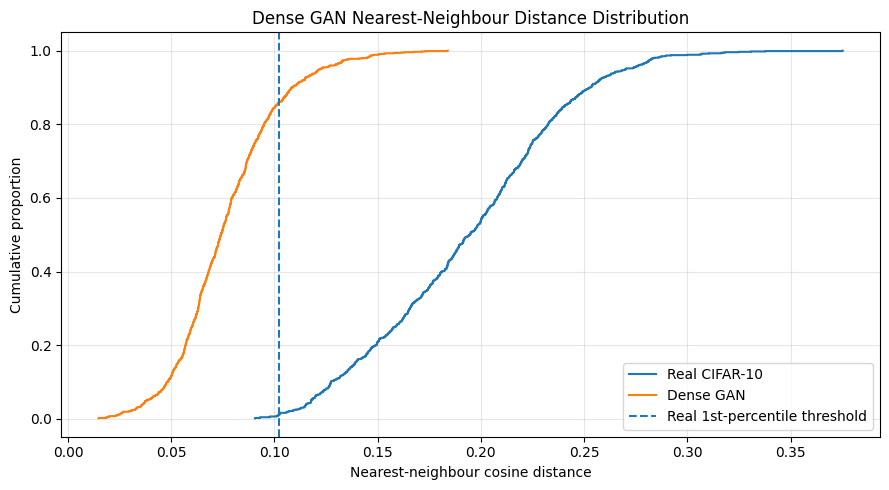

Saved nearest-distance plot: [local project directory]/grids/G01_dense_seed42_nearest_distance_ecdf.png


In [ ]:
dense_nearest_distance_plot_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_nearest_distance_ecdf.png"
)

real_sorted_distances = np.sort(
    real_nearest_distances
)

generated_sorted_distances = np.sort(
    generated_nearest_distances
)

real_ecdf = np.arange(
    1,
    len(real_sorted_distances) + 1,
) / len(real_sorted_distances)

generated_ecdf = np.arange(
    1,
    len(generated_sorted_distances) + 1,
) / len(generated_sorted_distances)

plt.figure(figsize=(9, 5))

plt.step(
    real_sorted_distances,
    real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    generated_sorted_distances,
    generated_ecdf,
    where="post",
    label="Dense GAN",
)

plt.axvline(
    near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "Dense GAN Nearest-Neighbour Distance Distribution"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dense_nearest_distance_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved nearest-distance plot: "
    f"{dense_nearest_distance_plot_path}"
)

**Interpretation**

The nearest-neighbour distance distribution for the Dense GAN is strongly shifted toward smaller distances than the real CIFAR-10 distribution.

Most generated images have another generated image that is very close in Inception feature space. At the real-data near-duplicate threshold of `0.102216`:

- approximately 1% of real CIFAR-10 images fall below the threshold
- 86% of Dense GAN images fall below the threshold

The separation between the two curves shows that the Dense GAN covers a much narrower feature distribution than the real dataset.

This supports the earlier conclusion that the model has not produced exact pixel duplicates, but repeatedly generates highly similar colours, textures, layouts, and vague object forms.

The result indicates severe feature-space clustering and partial mode collapse rather than complete collapse to one identical image.

#### Most similar generated-image pairs

The ten closest generated-image pairs are displayed to examine what the feature-space near-duplicate rate represents visually.

This helps determine whether the low distances correspond to:

- almost identical outputs
- repeated colour and texture templates
- similar foreground-background layouts
- recurring vague object shapes

In [ ]:
generated_nearest_indices = np.argmin(
    generated_distance_matrix,
    axis=1,
)

unique_pair_distances = {}

for image_index, neighbour_index in enumerate(
    generated_nearest_indices
):
    pair = tuple(
        sorted(
            (
                int(image_index),
                int(neighbour_index),
            )
        )
    )

    pair_distance = float(
        generated_distance_matrix[
            pair[0],
            pair[1],
        ]
    )

    if pair not in unique_pair_distances:
        unique_pair_distances[pair] = (
            pair_distance
        )

most_similar_pairs = sorted(
    unique_pair_distances.items(),
    key=lambda item: item[1],
)[:10]

dense_similar_pairs_path = (
    GRIDS_DIR
    / f"{DENSE_RUN_ID}_most_similar_pairs.png"
)

fig, axes = plt.subplots(
    5,
    4,
    figsize=(10, 13),
)

for pair_number, (
    pair,
    pair_distance,
) in enumerate(most_similar_pairs):
    row = pair_number // 2
    column = (pair_number % 2) * 2

    first_index, second_index = pair

    axes[row, column].imshow(
        generated_diversity_images[
            first_index
        ]
    )

    axes[row, column].set_title(
        f"Pair {pair_number + 1}A",
        fontsize=9,
    )

    axes[row, column].axis("off")

    axes[row, column + 1].imshow(
        generated_diversity_images[
            second_index
        ]
    )

    axes[row, column + 1].set_title(
        (
            f"Pair {pair_number + 1}B\n"
            f"Distance: {pair_distance:.4f}"
        ),
        fontsize=9,
    )

    axes[row, column + 1].axis("off")

plt.suptitle(
    "Dense GAN Most Similar Generated Pairs",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    dense_similar_pairs_path,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved most-similar pairs figure: "
    f"{dense_similar_pairs_path}"
)

Saved most-similar pairs figure: [local project directory]/grids/G01_dense_seed42_most_similar_pairs.png


**Interpretation**

The most similar generated pairs show that the Dense GAN repeatedly produces the same limited visual templates.

Pairs 1 to 8 and Pair 10 are dominated by a highly saturated pattern containing:

- a dark background
- bright white or yellow central regions
- scattered red, green, and blue pixels
- nearly identical foreground placement and overall composition

Pair 9 shows a different but still strongly repeated blue-green blurred template.

The paired images are not exact pixel copies, which agrees with the 0% exact-duplicate rate. However, their colours, textures, foreground positions, and broad layouts are extremely similar.

This demonstrates why exact-duplicate checking alone is insufficient. A generator can produce different pixel arrays while repeatedly sampling from a very narrow set of learned visual modes.

The Dense GAN therefore shows severe partial mode collapse:

- it has not collapsed to one identical image
- it still produces some variation across the full sample
- a large proportion of its outputs cluster around a small number of repeated templates
- the repeated templates are mostly noisy and not recognisable objects

This conclusion is supported consistently by:

- the 86% feature-space near-duplicate rate
- the low diversity ratio of `0.6648`
- the left-shifted nearest-neighbour distance distribution
- the visibly near-identical generated pairs
- the 0% Clear manual score

In [ ]:
dense_training_time_minutes = float(
    dense_history_df["epoch_time_seconds"].sum()
    / 60.0
)

dense_diversity_summary = (
    f"Diversity ratio to real: "
    f"{dense_diversity_ratio:.4f}; "
    f"near-duplicate rate: "
    f"{generated_near_duplicate_rate:.1f}%; "
    f"exact duplicate rate: "
    f"{generated_exact_duplicate_rate:.1f}%"
)

dense_master_df = update_models_metrics(
    {
        "run_id": DENSE_RUN_ID,
        "experiment_family": (
            "architecture_screen"
        ),
        "model": "Dense GAN",
        "main_change": (
            "Fully connected GAN foundation"
        ),
        "seed": DENSE_SEED,
        "epochs_completed": DENSE_EPOCHS,
        "selected_epoch": (
            DENSE_SELECTED_EPOCH
        ),
        "latent_dim": DENSE_LATENT_DIM,
        "batch_size": DENSE_BATCH_SIZE,
        "generator_parameters": (
            dense_generator.count_params()
        ),
        "adversary_parameters": (
            dense_discriminator.count_params()
        ),
        "development_fid": dense_fid_mean,
        "fid_std": dense_fid_std,
        "clear_count": dense_clear_count,
        "marginal_count": (
            dense_marginal_count
        ),
        "nonsense_count": (
            dense_nonsense_count
        ),
        "diversity_summary": (
            dense_diversity_summary
        ),
        "training_time_minutes": (
            dense_training_time_minutes
        ),
        "selected": False,
        "decision": (
            "Epoch 70 selected within the "
            "Dense GAN run. Poor recognisability "
            "and severe feature-space clustering. "
            "Architecture comparison pending."
        ),
    }
)

dense_master_row = dense_master_df.loc[
    dense_master_df["run_id"]
    == DENSE_RUN_ID
]

display(dense_master_row)

print(
    "Dense GAN results saved to "
    "models_metrics.csv."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
0,G01_dense_seed42,architecture_screen,Dense GAN,Fully connected GAN foundation,42,100,70,100,64,3836928,3803137,327.29971,0.187123,0,20,80,Diversity ratio to real: 0.6648; near-duplicat...,14.848162,False,Epoch 70 selected within the Dense GAN run. Po...


Dense GAN results saved to models_metrics.csv.


#### Dense GAN findings and limitations

The Dense GAN received a complete 100-epoch architecture-screen run and was evaluated using training diagnostics, fixed and uncurated grids, milestone FID, repeated FID, manual scoring, feature-space diversity, near-duplicate analysis, and compute evidence.

##### Result summary

| Evidence | Dense GAN result |
|---|---:|
| Selected checkpoint | Epoch 70 |
| Repeated development FID | `327.2997 ± 0.1871` |
| Clear | 0 out of 100 |
| Marginal | 20 out of 100 |
| Nonsense | 80 out of 100 |
| Diversity ratio to real CIFAR-10 | `0.6648` |
| Generated near-duplicate rate | `86.0%` |
| Exact duplicate rate | `0.0%` |
| Generator parameters | 3,836,928 |
| Discriminator parameters | 3,803,137 |
| Recorded training time | 14.85 minutes |

##### Findings

The Dense GAN learned some low-level characteristics of CIFAR-10, including colour variation, contrast, foreground-background separation, and broad texture patterns. It therefore did more than produce one constant image or completely random noise.

However, it did not learn reliable object structure. None of the 100 uncurated images was sufficiently recognisable to receive a Clear score, while 80% were classified as Nonsense.

The feature-space results also indicate severe restriction of the generated distribution. Although no exact pixel duplicates were found, 86% of generated images had an unusually close generated neighbour, and the generated diversity was only about 66.5% of the real-image reference. Inspection of the closest pairs confirmed repeated colour, texture, and layout templates.

Training evidence showed that the discriminator became increasingly dominant. After a temporarily more balanced period during the earlier epochs, real-image scores increased while generated-image scores decreased. Additional training after epoch 70 increased FID and did not improve visual recognisability.

The descriptor comparison showed that these low-level characteristics were not accurately matched. The generated sample was brighter, more green-blue biased, substantially more saturated, and lower in average contrast and edge strength than real CIFAR-10. Brightness and colour variation were also compressed, while edge-strength variation was unusually wide because the model mixed blurry outputs with highly noisy artifacts.

##### Checkpoint decision

Epoch 70 was selected because it achieved the lowest milestone FID and did not show visual deterioration relative to epoch 50. Epochs 90 and 100 had substantially worse FID and stronger visual artifacts.

This is a checkpoint decision within the Dense GAN run, not the final architecture decision.

##### Limitations

- Flattening removes explicit spatial neighbourhood information.
- Dense layers do not provide the local receptive fields or hierarchical feature learning used by convolutional models.
- The generator learned colour and texture more successfully than semantic structure.
- The adversarial contest became imbalanced in favour of the discriminator.
- The model showed severe feature-space clustering and partial mode collapse.
- FID uses an ImageNet-trained feature extractor on resized CIFAR-10 images and is therefore interpreted comparatively rather than absolutely.

##### Architecture-screen status

The Dense GAN is retained as a completed and fairly evaluated baseline.

It is not currently marked as the selected architecture. DCGAN and WGAN-GP must receive the same architecture-screen opportunity before one foundation is carried into the controlled improvement experiments.

### 5.2 DCGAN

#### Question

Does convolution substantially improve spatial coherence, recognisability, FID, and diversity over the Dense GAN?

#### Rationale

The Dense GAN flattened every image into a 3,072-value vector. This removed explicit information about local pixel neighbourhoods and spatial feature hierarchies.

DCGAN instead uses:

- transposed convolutions to progressively construct spatial image features
- convolutions to detect local patterns in real and generated images
- shared filters that can recognise similar features at different image locations
- hierarchical feature learning across multiple resolutions

The model therefore has an architectural bias that is better suited to image generation.

#### Hypothesis

DCGAN is expected to produce:

- more coherent foreground shapes
- stronger local texture structure
- more recognisable CIFAR-10 objects
- lower FID
- greater feature-space diversity
- less repetition than the Dense GAN

This remains a hypothesis until the complete DCGAN evaluation is performed.

#### Controlled settings

| Setting | Value |
|---|---:|
| Run ID | `G02_dcgan_seed42` |
| Training images | 50,000 |
| Image representation | RGB `float32` in `[-1, 1]` |
| Latent dimension | 100 |
| Batch size | 64 |
| Epoch budget | 100 |
| Training seed | 42 |
| Optimiser | Adam |
| Generator learning rate | `0.0002` |
| Discriminator learning rate | `0.0002` |
| Adam `beta_1` | `0.5` |
| Adam `beta_2` | `0.999` |
| Update ratio | `1D:1G` |
| Augmentation | None |
| Label smoothing | None |
| Dropout | None |

The data, training budget, latent distribution, seed, checkpoint schedule, and evaluation pipeline remain aligned with the Dense GAN architecture screen.

The Dense GAN and DCGAN are not required to have identical parameter counts. Both use conventional, credible architectures, and meaningful capacity differences are reported during the final comparison.

In [ ]:
# DCGAN architecture-screen settings
DCGAN_RUN_ID = "G02_dcgan_seed42"

DCGAN_SEED = PRIMARY_SEED
DCGAN_LATENT_DIM = 100
DCGAN_BATCH_SIZE = 64
DCGAN_EPOCHS = 100

DCGAN_GENERATOR_LR = 2e-4
DCGAN_DISCRIMINATOR_LR = 2e-4
DCGAN_BETA_1 = 0.5
DCGAN_BETA_2 = 0.999

DCGAN_CHECKPOINT_INTERVAL = 10
DCGAN_GRID_INTERVAL = 10
DCGAN_EVALUATION_EPOCHS = (50, 70, 90, 100)
DCGAN_MAX_CHECKPOINTS = 3

DCGAN_FIXED_GRID_SIZE = 25
DCGAN_MANUAL_SCORE_SIZE = 100

# Persistent paths
DCGAN_CHECKPOINT_DIR = (
    CHECKPOINTS_DIR / DCGAN_RUN_ID
)

DCGAN_HISTORY_PATH = (
    HISTORIES_DIR / f"{DCGAN_RUN_ID}.csv"
)

DCGAN_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / f"{DCGAN_RUN_ID}_generator.weights.h5"
)

DCGAN_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / f"{DCGAN_RUN_ID}_discriminator.weights.h5"
)

DCGAN_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Run ID:          {DCGAN_RUN_ID}")
print(f"Checkpoint path: {DCGAN_CHECKPOINT_DIR}")
print(f"History path:    {DCGAN_HISTORY_PATH}")
print(f"Epoch budget:    {DCGAN_EPOCHS}")
print(f"Batch size:      {DCGAN_BATCH_SIZE}")
print(f"Latent dim:      {DCGAN_LATENT_DIM}")

Run ID:          G02_dcgan_seed42
Checkpoint path: [local project directory]/checkpoints/G02_dcgan_seed42
History path:    [local project directory]/histories/G02_dcgan_seed42.csv
Epoch budget:    100
Batch size:      64
Latent dim:      100


#### Architecture design

##### Generator

```text
Latent vector, 100
→ Dense 4 × 4 × 256
→ Batch Normalisation
→ LeakyReLU
→ Reshape to 4 × 4 × 256
→ Conv2DTranspose 128, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Conv2DTranspose 64, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Conv2DTranspose 3, stride 2
→ tanh
→ Output 32 × 32 × 3
```

The generator begins with a compact `4 × 4` spatial representation and progressively increases its resolution:

```text
4 × 4 → 8 × 8 → 16 × 16 → 32 × 32
```

Transposed convolutions learn how spatial features should be expanded rather than treating each output pixel independently.

Batch Normalisation is used in the hidden generator blocks to support stable activation scaling. The final layer omits Batch Normalisation and uses `tanh` to match the `[-1, 1]` image range.

##### Discriminator

```text
Input 32 × 32 × 3
→ Conv2D 64, stride 2
→ LeakyReLU
→ Conv2D 128, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Conv2D 256, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Flatten
→ Dense 1
→ sigmoid
```

The discriminator progressively reduces the spatial resolution:

```text
32 × 32 → 16 × 16 → 8 × 8 → 4 × 4
```

The first discriminator block omits Batch Normalisation because it processes raw images directly. Hidden convolutional blocks use Batch Normalisation as part of the conventional DCGAN formulation.

No dropout, label smoothing, or additional stabilisation is included in this foundation run. Those methods remain available for later controlled experiments.

In [ ]:
# Build the DCGAN generator.
def build_dcgan_generator(latent_dim):

    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.Conv2DTranspose(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                3,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="DCGAN_Generator",
    )

    return model

In [ ]:
# Build the DCGAN discriminator.
def build_dcgan_discriminator():

    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=weight_init,
            ),
        ],
        name="DCGAN_Discriminator",
    )

    return model

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(
    DCGAN_SEED
)

dcgan_generator = (
    build_dcgan_generator(
        DCGAN_LATENT_DIM
    )
)

dcgan_discriminator = (
    build_dcgan_discriminator()
)

print("DCGAN generator")
dcgan_generator.summary()

print("\nDCGAN discriminator")
dcgan_discriminator.summary()

print("\nParameter counts")

print(
    f"Generator:     "
    f"{dcgan_generator.count_params():,}"
)

print(
    f"Discriminator: "
    f"{dcgan_discriminator.count_params():,}"
)

DCGAN generator


Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,187 (4.14 MB)

 Trainable params: 1,076,611 (4.11 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,129 (2.53 MB)

 Trainable params: 663,361 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)


Parameter counts
Generator:     1,085,187
Discriminator: 664,129


In [ ]:
dcgan_test_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=DCGAN_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

dcgan_test_images = dcgan_generator(
    dcgan_test_noise,
    training=False,
)

dcgan_test_scores = (
    dcgan_discriminator(
        dcgan_test_images,
        training=False,
    )
)

print("Generated image batch")
print(f"Shape: {dcgan_test_images.shape}")
print(f"Dtype: {dcgan_test_images.dtype}")

print(
    "Range: "
    f"[{tf.reduce_min(dcgan_test_images).numpy():.4f}, "
    f"{tf.reduce_max(dcgan_test_images).numpy():.4f}]"
)

print("\nDiscriminator output")
print(f"Shape: {dcgan_test_scores.shape}")

print(
    "Range: "
    f"[{tf.reduce_min(dcgan_test_scores).numpy():.4f}, "
    f"{tf.reduce_max(dcgan_test_scores).numpy():.4f}]"
)

assert dcgan_test_images.shape == (
    8,
    32,
    32,
    3,
)

assert dcgan_test_images.dtype == tf.float32

assert (
    tf.reduce_min(
        dcgan_test_images
    ).numpy()
    >= -1.0
)

assert (
    tf.reduce_max(
        dcgan_test_images
    ).numpy()
    <= 1.0
)

assert dcgan_test_scores.shape == (
    8,
    1,
)

assert (
    tf.reduce_min(
        dcgan_test_scores
    ).numpy()
    >= 0.0
)

assert (
    tf.reduce_max(
        dcgan_test_scores
    ).numpy()
    <= 1.0
)

del dcgan_test_noise
del dcgan_test_images
del dcgan_test_scores

print(
    "\nDCGAN architecture "
    "validation passed."
)

Generated image batch
Shape: (8, 32, 32, 3)
Dtype: <dtype: 'float32'>
Range: [-0.0300, 0.0304]

Discriminator output
Shape: (8, 1)
Range: [0.4999, 0.5000]

DCGAN architecture validation passed.


#### Training objective and optimiser

DCGAN uses the same standard adversarial binary objective as the Dense GAN.

During the discriminator update:

- real images are assigned target values of 1
- generated images are assigned target values of 0
- only discriminator variables are optimised

During the generator update:

- generated images are assigned target values of 1
- only generator variables are optimised

Both networks use Adam with:

```text
learning rate = 0.0002
beta_1 = 0.5
beta_2 = 0.999
```

The generator and discriminator use separate optimiser objects so their complete states can be saved and restored.

In [ ]:
dcgan_bce = losses.BinaryCrossentropy(
    from_logits=False
)

dcgan_generator_optimizer = (
    optimizers.Adam(
        learning_rate=(
            DCGAN_GENERATOR_LR
        ),
        beta_1=DCGAN_BETA_1,
        beta_2=DCGAN_BETA_2,
    )
)

dcgan_discriminator_optimizer = (
    optimizers.Adam(
        learning_rate=(
            DCGAN_DISCRIMINATOR_LR
        ),
        beta_1=DCGAN_BETA_1,
        beta_2=DCGAN_BETA_2,
    )
)

# Create optimiser variables before
# checkpoint restoration.
dcgan_generator_optimizer.build(
    dcgan_generator.trainable_variables
)

dcgan_discriminator_optimizer.build(
    dcgan_discriminator.trainable_variables
)

print(
    "DCGAN loss and optimisers created."
)

DCGAN loss and optimisers created.


In [ ]:
dcgan_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=DCGAN_BATCH_SIZE,
        seed=DCGAN_SEED,
    )
)

dcgan_fixed_noise = (
    make_stateless_noise(
        sample_count=(
            DCGAN_FIXED_GRID_SIZE
        ),
        latent_dim=DCGAN_LATENT_DIM,
        seed=FIXED_LATENT_SEED,
    )
)

dcgan_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        dcgan_train_dataset
    ).numpy()
)

print(
    f"Batches per epoch: "
    f"{dcgan_batches_per_epoch}"
)

print(
    f"Fixed grid noise: "
    f"{dcgan_fixed_noise.shape}"
)

assert dcgan_batches_per_epoch == 782

assert dcgan_fixed_noise.shape == (
    25,
    100,
)

Batches per epoch: 782
Fixed grid noise: (25, 100)


#### Saved training artifacts

The DCGAN run follows the same persistence contract as the Dense GAN.

##### After every completed epoch

```text
histories/G02_dcgan_seed42.csv
```

##### Every 10 epochs and at the final epoch

```text
checkpoints/G02_dcgan_seed42/
grids/G02_dcgan_seed42_epoch010.png
...
grids/G02_dcgan_seed42_epoch100.png
```

Each full checkpoint contains:

- generator
- discriminator
- both optimisers
- completed epoch counter

##### Formal evaluation milestones

Both networks are saved at epochs 50, 70, 90, and 100:

```text
weights/G02_dcgan_seed42_epoch050_generator.weights.h5
weights/G02_dcgan_seed42_epoch050_discriminator.weights.h5
```

The matching generator and discriminator files ensure that an earlier selected checkpoint remains available even after older full checkpoints are pruned.

In [ ]:
dcgan_completed_epoch = tf.Variable(
    0,
    dtype=tf.int64,
    trainable=False,
    name="completed_epoch",
)

dcgan_checkpoint = tf.train.Checkpoint(
    epoch=dcgan_completed_epoch,
    generator=dcgan_generator,
    discriminator=dcgan_discriminator,
    generator_optimizer=(
        dcgan_generator_optimizer
    ),
    discriminator_optimizer=(
        dcgan_discriminator_optimizer
    ),
)

dcgan_checkpoint_manager = (
    tf.train.CheckpointManager(
        checkpoint=dcgan_checkpoint,
        directory=str(
            DCGAN_CHECKPOINT_DIR
        ),
        max_to_keep=(
            DCGAN_MAX_CHECKPOINTS
        ),
    )
)

if dcgan_checkpoint_manager.latest_checkpoint:
    dcgan_checkpoint.restore(
        dcgan_checkpoint_manager
        .latest_checkpoint
    )

    print(
        "Restored checkpoint: "
        f"{dcgan_checkpoint_manager.latest_checkpoint}"
    )

    print(
        "Restored completed epoch: "
        f"{int(dcgan_completed_epoch.numpy())}"
    )

else:
    print("No existing checkpoint found.")
    print("DCGAN will begin from epoch 1.")

No existing checkpoint found.
DCGAN will begin from epoch 1.


In [ ]:
dcgan_history = load_and_align_history(
    history_path=DCGAN_HISTORY_PATH,
    columns=STANDARD_GAN_HISTORY_COLUMNS,
    restored_epoch=int(
        dcgan_completed_epoch.numpy()
    ),
)

print(
    f"History rows available: "
    f"{len(dcgan_history)}"
)

if not dcgan_history.empty:
    print(
        f"Latest history epoch: "
        f"{int(dcgan_history['epoch'].max())}"
    )

History rows available: 0


#### Alternating DCGAN updates

Each batch performs one discriminator update followed by one generator update.

##### Discriminator update

The generator creates a fake batch using inference behaviour. The discriminator then evaluates both real and generated images using training behaviour.

Only discriminator variables receive gradients.

##### Generator update

The generator creates a new fake batch using training behaviour, allowing its Batch Normalisation layers to learn normally.

The discriminator is also called using training behaviour so its hidden Batch Normalisation layers use the current generated batch statistics. However, gradients are applied only to the generator variables. The discriminator's trainable weights are not optimised during this step.

This behaviour is kept explicit rather than hidden inside a compiled combined model.

In [ ]:
@tf.function
def dcgan_train_step(real_images):
    current_batch_size = tf.shape(
        real_images
    )[0]

    # 1. Update the discriminator
    discriminator_noise = tf.random.normal(
        shape=(
            current_batch_size,
            DCGAN_LATENT_DIM,
        )
    )

    fake_images_for_discriminator = (
        dcgan_generator(
            discriminator_noise,
            training=False,
        )
    )

    fake_images_for_discriminator = (
        tf.stop_gradient(
            fake_images_for_discriminator
        )
    )

    with tf.GradientTape() as discriminator_tape:
        real_predictions = (
            dcgan_discriminator(
                real_images,
                training=True,
            )
        )

        fake_predictions = (
            dcgan_discriminator(
                fake_images_for_discriminator,
                training=True,
            )
        )

        real_loss = dcgan_bce(
            tf.ones_like(
                real_predictions
            ),
            real_predictions,
        )

        fake_loss = dcgan_bce(
            tf.zeros_like(
                fake_predictions
            ),
            fake_predictions,
        )

        discriminator_loss = (
            real_loss + fake_loss
        ) / 2.0

    discriminator_gradients = (
        discriminator_tape.gradient(
            discriminator_loss,
            dcgan_discriminator
            .trainable_variables,
        )
    )

    dcgan_discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            dcgan_discriminator
            .trainable_variables,
        )
    )

    # 2. Update the generator
    generator_noise = tf.random.normal(
        shape=(
            current_batch_size,
            DCGAN_LATENT_DIM,
        )
    )

    with tf.GradientTape() as generator_tape:
        generated_images = dcgan_generator(
            generator_noise,
            training=True,
        )

        generated_predictions = (
            dcgan_discriminator(
                generated_images,
                training=True,
            )
        )

        generator_loss = dcgan_bce(
            tf.ones_like(
                generated_predictions
            ),
            generated_predictions,
        )

    generator_gradients = (
        generator_tape.gradient(
            generator_loss,
            dcgan_generator
            .trainable_variables,
        )
    )

    dcgan_generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            dcgan_generator
            .trainable_variables,
        )
    )

    return {
        "generator_loss": generator_loss,
        "discriminator_loss": (
            discriminator_loss
        ),
        "real_score": tf.reduce_mean(
            real_predictions
        ),
        "fake_score": tf.reduce_mean(
            fake_predictions
        ),
    }

In [ ]:
# Save the current DCGAN checkpoint and fixed grid.
def save_dcgan_state(epoch):

    checkpoint_path = (
        dcgan_checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        GRIDS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    save_generated_grid(
        generator=dcgan_generator,
        noise=dcgan_fixed_noise,
        save_path=grid_path,
        title=(
            f"DCGAN, Epoch {epoch}"
        ),
    )

    print(
        f"Saved checkpoint: "
        f"{checkpoint_path}"
    )

    print(
        f"Saved grid:       "
        f"{grid_path}"
    )

In [ ]:
# Train or resume DCGAN to the requested epoch.
def train_dcgan(target_epochs):

    start_epoch = (
        int(dcgan_completed_epoch.numpy())
        + 1
    )

    if start_epoch > target_epochs:
        print(
            "DCGAN is already trained "
            f"through epoch "
            f"{int(dcgan_completed_epoch.numpy())}."
        )

        return load_and_align_history(
            history_path=DCGAN_HISTORY_PATH,
            columns=(
                STANDARD_GAN_HISTORY_COLUMNS
            ),
            restored_epoch=int(
                dcgan_completed_epoch.numpy()
            ),
        )

    print(
        f"Training DCGAN from epoch "
        f"{start_epoch} to {target_epochs}."
    )

    for epoch in range(
        start_epoch,
        target_epochs + 1,
    ):
        epoch_start_time = time.time()

        generator_loss_mean = (
            keras.metrics.Mean()
        )

        discriminator_loss_mean = (
            keras.metrics.Mean()
        )

        real_score_mean = (
            keras.metrics.Mean()
        )

        fake_score_mean = (
            keras.metrics.Mean()
        )

        for real_images in dcgan_train_dataset:
            batch_results = dcgan_train_step(
                real_images
            )

            generator_loss_mean.update_state(
                batch_results[
                    "generator_loss"
                ]
            )

            discriminator_loss_mean.update_state(
                batch_results[
                    "discriminator_loss"
                ]
            )

            real_score_mean.update_state(
                batch_results[
                    "real_score"
                ]
            )

            fake_score_mean.update_state(
                batch_results[
                    "fake_score"
                ]
            )

        epoch_time = (
            time.time() - epoch_start_time
        )

        epoch_results = {
            "epoch": epoch,
            "generator_loss": float(
                generator_loss_mean.result()
                .numpy()
            ),
            "discriminator_loss": float(
                discriminator_loss_mean.result()
                .numpy()
            ),
            "real_score": float(
                real_score_mean.result()
                .numpy()
            ),
            "fake_score": float(
                fake_score_mean.result()
                .numpy()
            ),
            "epoch_time_seconds": float(
                epoch_time
            ),
        }

        numeric_results = np.array(
            [
                epoch_results[
                    "generator_loss"
                ],
                epoch_results[
                    "discriminator_loss"
                ],
                epoch_results[
                    "real_score"
                ],
                epoch_results[
                    "fake_score"
                ],
                epoch_results[
                    "epoch_time_seconds"
                ],
            ]
        )

        if not np.isfinite(
            numeric_results
        ).all():
            raise FloatingPointError(
                "Non-finite DCGAN training "
                f"value detected at epoch "
                f"{epoch}."
            )

        dcgan_completed_epoch.assign(
            epoch
        )

        # Save history after every epoch.
        dcgan_history = save_epoch_history(
            history_path=DCGAN_HISTORY_PATH,
            row=epoch_results,
            columns=(
                STANDARD_GAN_HISTORY_COLUMNS
            ),
        )

        # Save matching milestone weights.
        if epoch in DCGAN_EVALUATION_EPOCHS:
            milestone_generator_path = (
                WEIGHTS_DIR
                / (
                    f"{DCGAN_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            milestone_discriminator_path = (
                WEIGHTS_DIR
                / (
                    f"{DCGAN_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "discriminator.weights.h5"
                )
            )

            dcgan_generator.save_weights(
                milestone_generator_path
            )

            dcgan_discriminator.save_weights(
                milestone_discriminator_path
            )

            print(
                "Saved milestone generator: "
                f"{milestone_generator_path}"
            )

            print(
                "Saved milestone discriminator: "
                f"{milestone_discriminator_path}"
            )

        # Save full checkpoint and grid.
        if (
            epoch
            % DCGAN_CHECKPOINT_INTERVAL
            == 0
            or epoch == target_epochs
        ):
            save_dcgan_state(
                epoch=epoch
            )

        print(
            f"Epoch {epoch:03d}/{target_epochs} "
            f"| G loss: "
            f"{epoch_results['generator_loss']:.4f} "
            f"| D loss: "
            f"{epoch_results['discriminator_loss']:.4f} "
            f"| Real: "
            f"{epoch_results['real_score']:.4f} "
            f"| Fake: "
            f"{epoch_results['fake_score']:.4f} "
            f"| Time: "
            f"{epoch_results['epoch_time_seconds']:.1f}s"
        )

    total_training_minutes = float(
        dcgan_history[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    update_models_metrics(
        {
            "run_id": DCGAN_RUN_ID,
            "experiment_family": (
                "architecture_screen"
            ),
            "model": "DCGAN",
            "main_change": (
                "Convolutional GAN foundation"
            ),
            "seed": DCGAN_SEED,
            "epochs_completed": int(
                dcgan_completed_epoch.numpy()
            ),
            "latent_dim": (
                DCGAN_LATENT_DIM
            ),
            "batch_size": (
                DCGAN_BATCH_SIZE
            ),
            "generator_parameters": (
                dcgan_generator.count_params()
            ),
            "adversary_parameters": (
                dcgan_discriminator.count_params()
            ),
            "training_time_minutes": (
                total_training_minutes
            ),
        }
    )

    print(
        "\nDCGAN training complete."
    )

    print(
        f"Completed epoch: "
        f"{int(dcgan_completed_epoch.numpy())}"
    )

    print(
        f"Total recorded training time: "
        f"{total_training_minutes:.2f} minutes"
    )

    return dcgan_history

#### Training or resuming DCGAN

The following cell trains DCGAN to epoch 100.

If a valid checkpoint already exists, the model, optimisers, completed epoch, and aligned history are restored before training continues.

During training:

- history is saved after every completed epoch
- matching generator and discriminator weights are saved at epochs 50, 70, 90, and 100
- full checkpoints and fixed grids are saved every 10 epochs
- the master metrics CSV is updated after training completes

The official test set remains unused.

In [ ]:
dcgan_history = train_dcgan(
    target_epochs=DCGAN_EPOCHS
)

Training DCGAN from epoch 1 to 100.
Epoch 001/100 | G loss: 1.0199 | D loss: 0.1063 | Real: 0.9316 | Fake: 0.0689 | Time: 16.2s
Epoch 002/100 | G loss: 0.9989 | D loss: 0.2806 | Real: 0.8052 | Fake: 0.1880 | Time: 11.7s
Epoch 003/100 | G loss: 0.7372 | D loss: 0.1338 | Real: 0.9043 | Fake: 0.0934 | Time: 11.7s
Epoch 004/100 | G loss: 0.5132 | D loss: 0.1605 | Real: 0.8915 | Fake: 0.1076 | Time: 11.7s
Epoch 005/100 | G loss: 0.8196 | D loss: 0.1538 | Real: 0.8960 | Fake: 0.1032 | Time: 11.7s
Epoch 006/100 | G loss: 1.3574 | D loss: 0.1436 | Real: 0.8987 | Fake: 0.0999 | Time: 11.6s
Epoch 007/100 | G loss: 1.2905 | D loss: 0.1030 | Real: 0.9227 | Fake: 0.0758 | Time: 11.6s
Epoch 008/100 | G loss: 1.0433 | D loss: 0.0662 | Real: 0.9541 | Fake: 0.0446 | Time: 11.6s
Epoch 009/100 | G loss: 0.9576 | D loss: 0.0585 | Real: 0.9589 | Fake: 0.0402 | Time: 11.6s
Saved checkpoint: [local project directory]/checkpoints/G02_dcgan_seed42/ckpt-10
Saved grid:       [local project directory]/grids/G02_d

/tmp/ipykernel_6496/4158530258.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


#### Training artifact verification

Before evaluating DCGAN, the saved artifacts are checked to confirm that the completed run can be recovered and analysed after a fresh Colab runtime.

The verification checks:

- 100 complete history rows
- epochs 1 to 100 with no duplicates
- finite recorded training values
- matching generator and discriminator weights at epochs 50, 70, 90 and 100
- fixed progression grids every 10 epochs
- a latest resumable checkpoint at epoch 100
- an initial DCGAN entry in `models_metrics.csv`

In [ ]:
# Verify the completed DCGAN artifacts
dcgan_saved_history = pd.read_csv(
    DCGAN_HISTORY_PATH
)

assert len(dcgan_saved_history) == 100

assert dcgan_saved_history["epoch"].tolist() == list(
    range(1, 101)
)

assert not dcgan_saved_history[
    STANDARD_GAN_HISTORY_COLUMNS
].isna().any().any()

assert np.isfinite(
    dcgan_saved_history[
        [
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ]
    ].to_numpy()
).all()

dcgan_milestone_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in DCGAN_EVALUATION_EPOCHS
}

dcgan_milestone_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch in DCGAN_EVALUATION_EPOCHS
}

dcgan_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        DCGAN_GRID_INTERVAL,
        DCGAN_EPOCHS + 1,
        DCGAN_GRID_INTERVAL,
    )
}

for epoch, path in (
    dcgan_milestone_generator_paths.items()
):
    assert path.exists(), (
        f"Missing epoch {epoch} generator weights"
    )

for epoch, path in (
    dcgan_milestone_discriminator_paths.items()
):
    assert path.exists(), (
        f"Missing epoch {epoch} discriminator weights"
    )

for epoch, path in dcgan_grid_paths.items():
    assert path.exists(), (
        f"Missing epoch {epoch} progression grid"
    )

assert (
    dcgan_checkpoint_manager.latest_checkpoint
    is not None
)

assert (
    int(dcgan_completed_epoch.numpy())
    == 100
)

models_metrics_df = pd.read_csv(
    MODELS_METRICS_PATH
)

assert DCGAN_RUN_ID in (
    models_metrics_df["run_id"]
    .astype(str)
    .tolist()
)

dcgan_checkpoint_files = sorted(
    DCGAN_CHECKPOINT_DIR.glob("ckpt-*")
)

dcgan_training_minutes = float(
    dcgan_saved_history[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

print("DCGAN artifact verification passed.")
print(
    f"History rows: "
    f"{len(dcgan_saved_history)}"
)
print(
    "Milestone generator weights: "
    f"{list(dcgan_milestone_generator_paths)}"
)
print(
    "Milestone discriminator weights: "
    f"{list(dcgan_milestone_discriminator_paths)}"
)
print(
    "Progression grids: "
    f"{len(dcgan_grid_paths)}"
)
print(
    "Latest checkpoint: "
    f"{dcgan_checkpoint_manager.latest_checkpoint}"
)
print(
    "Checkpoint files currently retained: "
    f"{len(dcgan_checkpoint_files)}"
)
print(
    "Recorded training time: "
    f"{dcgan_training_minutes:.2f} minutes"
)
print(
    "Initial models_metrics.csv row found."
)

DCGAN artifact verification passed.
History rows: 100
Milestone generator weights: [50, 70, 90, 100]
Milestone discriminator weights: [50, 70, 90, 100]
Progression grids: 10
Latest checkpoint: [local project directory]/checkpoints/G02_dcgan_seed42/ckpt-100
Checkpoint files currently retained: 6
Recorded training time: 19.47 minutes
Initial models_metrics.csv row found.


#### Training diagnostics

The DCGAN training history is examined before generated-image quality is evaluated.

The following plots show:

- generator and discriminator losses
- mean discriminator scores for real and generated images

These values are used to diagnose adversarial balance and stability. They do not directly determine generated-image quality, so checkpoint selection will also use fixed-seed grids and development FID.

In [ ]:
dcgan_history_df = pd.read_csv(
    DCGAN_HISTORY_PATH
)

dcgan_loss_plot_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_training_losses.png"
)

dcgan_score_plot_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_training_scores.png"
)

# Generator and discriminator losses
plt.figure(figsize=(10, 5))

plt.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["generator_loss"],
    label="Generator loss",
)

plt.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["discriminator_loss"],
    label="Discriminator loss",
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dcgan_loss_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

# Mean discriminator scores
plt.figure(figsize=(10, 5))

plt.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["real_score"],
    label="Mean real score",
)

plt.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["fake_score"],
    label="Mean generated score",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Uncertain discriminator",
)

plt.xlabel("Epoch")
plt.ylabel("Mean discriminator probability")
plt.title("DCGAN Discriminator Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dcgan_score_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(f"Saved loss plot:  {dcgan_loss_plot_path}")
print(f"Saved score plot: {dcgan_score_plot_path}")

Saved loss plot:  [local project directory]/grids/G02_dcgan_seed42_training_losses.png
Saved score plot: [local project directory]/grids/G02_dcgan_seed42_training_scores.png


**Interpretation**

DCGAN completed all 100 epochs without non-finite values or a technical training failure. However, the discriminator remained substantially stronger than the generator throughout most of training.

The generator loss generally increased:

- approximately `1.0` during the early epochs
- approximately `3.0` by epoch 30
- approximately `4.0` by epoch 60
- approximately `5.0` by epoch 100

At the same time, the discriminator loss remained low, generally between approximately `0.05` and `0.18`.

The discriminator-score plot supports the same diagnosis:

- real-image scores remained mostly between approximately `0.87` and `0.95`
- generated-image scores remained mostly between approximately `0.05` and `0.13`
- the two distributions were clearly separated throughout training

At epoch 100:

| Metric | Value |
|---|---:|
| Generator loss | 5.0284 |
| Discriminator loss | 0.0649 |
| Mean real score | 0.9538 |
| Mean generated score | 0.0462 |

These values indicate strong discriminator confidence and adversarial imbalance.

However, this does not mean that the generator failed. Unlike the Dense GAN, the DCGAN progression grids show major visual improvement despite the worsening generator loss. The loss is measured against the current discriminator, which also becomes more capable throughout training.

The generated images, milestone FID, diversity, and manual recognisability therefore provide more meaningful model-selection evidence than the loss magnitude alone.

#### Fixed-seed progression

The same 25 stateless latent vectors were used every 10 epochs.

This allows the progression grids to be compared without changes in the latent inputs. The comparison focuses on:

- emergence of coherent spatial structure
- changes in colour and texture
- visual diversity
- repeated patterns
- checkerboard artifacts
- deterioration or collapse during later training

In [ ]:
dcgan_progression_epochs = list(
    range(
        DCGAN_GRID_INTERVAL,
        DCGAN_EPOCHS + 1,
        DCGAN_GRID_INTERVAL,
    )
)

dcgan_progression_summary_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_progression_summary.png"
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8),
)

for axis, epoch in zip(
    axes.flat,
    dcgan_progression_epochs,
):
    grid_path = (
        GRIDS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    grid_image = plt.imread(
        grid_path
    )

    axis.imshow(
        grid_image
    )

    axis.set_title(
        f"Epoch {epoch}"
    )

    axis.axis("off")

plt.suptitle(
    "DCGAN Fixed-Seed Progression",
    fontsize=16,
)

plt.tight_layout()

plt.savefig(
    dcgan_progression_summary_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved progression summary: "
    f"{dcgan_progression_summary_path}"
)

Saved progression summary: [local project directory]/grids/G02_dcgan_seed42_progression_summary.png


**Interpretation**

The fixed-seed progression shows a substantial improvement over the Dense GAN.

At epoch 10, the outputs are mostly blurry and poorly structured, although some foreground-background separation has already emerged.

By epoch 20, the generator begins producing more organised scenes with:

- clearer central objects
- recognisable colour regions
- stronger separation between foreground and background
- early animal-like and vehicle-like forms

Between epochs 30 and 50, the largest improvement occurs. Many fixed latent inputs produce visibly class-related structures, including possible:

- cars and trucks
- aircraft and ships
- horses, deer, birds, cats, and dogs

The exact class of several images remains uncertain, but the outputs contain substantially more coherent spatial organisation than the Dense GAN.

From approximately epoch 50 onward, the same latent inputs remain visually stable. Later epochs mainly show small changes in sharpness, colour, texture, and object boundaries rather than a complete change in generated content.

There is no obvious complete mode collapse in the fixed grid. The 25 outputs contain variation in:

- object type
- colour
- background
- pose
- foreground placement

No severe checkerboard pattern dominates the sample, although some images remain blurry or contain local transposed-convolution artifacts.

Visually, epochs 50, 70, 90, and 100 all appear credible candidates. The progression alone does not provide a sufficiently clear reason to select one of them. Development FID is therefore required to identify whether the feature-distribution quality improves, plateaus, or deteriorates during the later epochs.

#### Milestone development FID

Generator checkpoints from epochs 50, 70, 90, and 100 are evaluated using the same development FID protocol used for the Dense GAN.

Each checkpoint generates 5,000 images using the same stateless latent seed. All checkpoints are compared against the same InceptionV3 statistics calculated from the full 50,000-image CIFAR-10 training set.

Using the same:

- generated sample count
- latent seed
- feature extractor
- real reference
- image preprocessing
- FID implementation

ensures that the Dense GAN, DCGAN, and later WGAN-GP results remain directly comparable.

The lowest FID will be considered together with progression grids and training stability. It will not automatically override clear visual deterioration or collapse.

In [ ]:
DCGAN_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{DCGAN_RUN_ID}_fid_results.csv"
)

print(
    f"DCGAN FID results path: "
    f"{DCGAN_FID_RESULTS_PATH}"
)

DCGAN FID results path: [local project directory]/histories/G02_dcgan_seed42_fid_results.csv


In [ ]:
dcgan_eval_generator = build_dcgan_generator(
    DCGAN_LATENT_DIM
)

dcgan_milestone_fid_rows = []

for epoch in DCGAN_EVALUATION_EPOCHS:
    milestone_path = (
        WEIGHTS_DIR
        / (
            f"{DCGAN_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )

    dcgan_eval_generator.load_weights(
        milestone_path
    )

    generated_images = generate_images_uint8(
        generator=dcgan_eval_generator,
        sample_count=ARCH_FID_SAMPLE_COUNT,
        latent_dim=DCGAN_LATENT_DIM,
        seed=ARCH_FID_SEEDS[0],
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=ARCH_FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    dcgan_milestone_fid_rows.append(
        {
            "evaluation": "milestone",
            "epoch": epoch,
            "seed": ARCH_FID_SEEDS[0],
            "sample_count": ARCH_FID_SAMPLE_COUNT,
            "fid": fid_value,
        }
    )

    print(
        f"Epoch {epoch:03d} "
        f"development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()

dcgan_milestone_fid_df = pd.DataFrame(
    dcgan_milestone_fid_rows
)

dcgan_milestone_fid_df.to_csv(
    DCGAN_FID_RESULTS_PATH,
    index=False,
)

display(
    dcgan_milestone_fid_df.round(4)
)

print(
    "Saved milestone FID results: "
    f"{DCGAN_FID_RESULTS_PATH}"
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 42.8621


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 41.8413


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 37.0242


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 36.7759


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,42.8621
1,milestone,70,1001,5000,41.8413
2,milestone,90,1001,5000,37.0242
3,milestone,100,1001,5000,36.7759


Saved milestone FID results: [local project directory]/histories/G02_dcgan_seed42_fid_results.csv


In [ ]:
dcgan_milestone_diagnostics = (
    dcgan_history_df.loc[
        dcgan_history_df["epoch"].isin(
            DCGAN_EVALUATION_EPOCHS
        ),
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ],
    ]
    .copy()
)

dcgan_checkpoint_evidence_df = (
    dcgan_milestone_diagnostics.merge(
        dcgan_milestone_fid_df[
            [
                "epoch",
                "fid",
            ]
        ],
        on="epoch",
        how="left",
    )
)

display(
    dcgan_checkpoint_evidence_df.round(4)
)

,epoch,generator_loss,discriminator_loss,real_score,fake_score,epoch_time_seconds,fid
0,50,3.7834,0.1473,0.9032,0.0967,11.6117,42.8621
1,70,4.2320,0.1049,0.9276,0.0719,11.6375,41.8413
2,90,4.7088,0.0943,0.9414,0.0584,11.6949,37.0242
3,100,5.0284,0.0649,0.9538,0.0462,11.5891,36.7759


**Interpretation**

The DCGAN development FID improved across all four formal milestones:

| Epoch | Development FID |
|---:|---:|
| 50 | 42.8621 |
| 70 | 41.8413 |
| 90 | 37.0242 |
| 100 | **36.7759** |

Epoch 100 achieved the lowest development FID.

The improvement was not uniform:

- epoch 70 improved by `1.0208` compared with epoch 50
- epoch 90 improved by `4.8171` compared with epoch 70
- epoch 100 improved by only `0.2483` compared with epoch 90

The small difference between epochs 90 and 100 suggests that DCGAN was beginning to plateau rather than continuing to make large gains.

The adversarial diagnostics moved in the opposite direction. From epoch 50 to epoch 100:

- generator loss increased from `3.7834` to `5.0284`
- discriminator loss decreased from `0.1473` to `0.0649`
- the mean real score increased from `0.9032` to `0.9538`
- the mean generated score decreased from `0.0967` to `0.0462`

This indicates increasingly strong discriminator dominance.

However, the fixed-seed progression does not show visual deterioration at epoch 100. The generated images retain coherent foreground-background structure, varied colours, and recognisable animal-like and vehicle-like forms. FID also continued to improve slightly.

The results therefore demonstrate why GAN checkpoint selection cannot rely on adversarial loss alone. Although the discriminator became increasingly confident, the generator's image distribution continued to improve according to both the visual progression and development FID.

FID remains a relative comparator because CIFAR-10 images are resized for an ImageNet-trained InceptionV3 feature extractor. Nevertheless, the agreement between the lowest FID and the absence of visible deterioration supports selecting epoch 100.

#### DCGAN checkpoint decision

**Selected checkpoint: epoch 100**

Epoch 100 is selected for the full DCGAN evaluation.

| Evidence | Finding |
|---|---|
| Development FID | Lowest milestone value, `36.7759` |
| Fixed-seed grid | No clear deterioration relative to epoch 90 |
| Spatial coherence | Recognisable animal-like and vehicle-like structures remain visible |
| Diversity in the grid | Varied object types, colours, backgrounds, and positions |
| Adversarial balance | Discriminator strongly dominant |
| Main caveat | FID improvement over epoch 90 is small |

Epoch 90 was a close alternative because its FID was only `0.2483` higher and its adversarial imbalance was slightly less severe. However, there is no visual evidence that the final ten epochs damaged the generator, while epoch 100 provides the strongest measured feature-distribution match.

This decision applies only within the DCGAN run. The selected epoch-100 checkpoint will now receive the full evaluation package:

- three repeated 5,000-image FID calculations
- fixed-seed and uncurated grids
- 100-image Clear, Marginal, and Nonsense scoring
- feature-space diversity analysis
- generated near-duplicate analysis
- nearest-neighbour distance comparison
- most-similar-pair inspection
- mode-collapse, stability, compute, and limitation reporting

In [ ]:
DCGAN_SELECTED_EPOCH = 100

if (
    DCGAN_SELECTED_EPOCH
    not in DCGAN_EVALUATION_EPOCHS
):
    raise ValueError(
        "Set DCGAN_SELECTED_EPOCH to "
        "50, 70, 90 or 100."
    )

print(
    "Selected DCGAN checkpoint: "
    f"epoch {DCGAN_SELECTED_EPOCH}"
)

Selected DCGAN checkpoint: epoch 100


In [ ]:
dcgan_selected_generator_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{DCGAN_RUN_ID}_"
        f"epoch{DCGAN_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

dcgan_selected_discriminator_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{DCGAN_RUN_ID}_"
        f"epoch{DCGAN_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)

dcgan_selected_generator = build_dcgan_generator(
    DCGAN_LATENT_DIM
)

dcgan_selected_discriminator = (
    build_dcgan_discriminator()
)

dcgan_selected_generator.load_weights(
    dcgan_selected_generator_milestone_path
)

dcgan_selected_discriminator.load_weights(
    dcgan_selected_discriminator_milestone_path
)

dcgan_selected_generator.save_weights(
    DCGAN_SELECTED_GENERATOR_PATH
)

dcgan_selected_discriminator.save_weights(
    DCGAN_SELECTED_DISCRIMINATOR_PATH
)

print(
    "Loaded generator milestone:     "
    f"{dcgan_selected_generator_milestone_path}"
)

print(
    "Loaded discriminator milestone: "
    f"{dcgan_selected_discriminator_milestone_path}"
)

print(
    "Saved selected generator:       "
    f"{DCGAN_SELECTED_GENERATOR_PATH}"
)

print(
    "Saved selected discriminator:   "
    f"{DCGAN_SELECTED_DISCRIMINATOR_PATH}"
)

Loaded generator milestone:     [local project directory]/weights/G02_dcgan_seed42_epoch100_generator.weights.h5
Loaded discriminator milestone: [local project directory]/weights/G02_dcgan_seed42_epoch100_discriminator.weights.h5
Saved selected generator:       [local project directory]/weights/G02_dcgan_seed42_generator.weights.h5
Saved selected discriminator:   [local project directory]/weights/G02_dcgan_seed42_discriminator.weights.h5


In [ ]:
dcgan_reload_generator = build_dcgan_generator(
    DCGAN_LATENT_DIM
)

dcgan_reload_discriminator = (
    build_dcgan_discriminator()
)

dcgan_reload_generator.load_weights(
    DCGAN_SELECTED_GENERATOR_PATH
)

dcgan_reload_discriminator.load_weights(
    DCGAN_SELECTED_DISCRIMINATOR_PATH
)

dcgan_reload_noise = make_stateless_noise(
    sample_count=16,
    latent_dim=DCGAN_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

# Verify the reloaded generator
dcgan_original_images = (
    dcgan_selected_generator(
        dcgan_reload_noise,
        training=False,
    )
)

dcgan_reloaded_images = (
    dcgan_reload_generator(
        dcgan_reload_noise,
        training=False,
    )
)

dcgan_generator_reload_difference = float(
    tf.reduce_max(
        tf.abs(
            dcgan_original_images
            - dcgan_reloaded_images
        )
    ).numpy()
)

# Verify the reloaded discriminator
# Both discriminators must receive the exact same image tensor.
dcgan_original_scores = (
    dcgan_selected_discriminator(
        dcgan_original_images,
        training=False,
    )
)

dcgan_reloaded_scores = (
    dcgan_reload_discriminator(
        dcgan_original_images,
        training=False,
    )
)

dcgan_discriminator_reload_difference = float(
    tf.reduce_max(
        tf.abs(
            dcgan_original_scores
            - dcgan_reloaded_scores
        )
    ).numpy()
)

# Directly compare saved model weights too.
dcgan_discriminator_weight_difference = max(
    float(
        tf.reduce_max(
            tf.abs(
                original_weight
                - reloaded_weight
            )
        ).numpy()
    )
    for original_weight, reloaded_weight in zip(
        dcgan_selected_discriminator.weights,
        dcgan_reload_discriminator.weights,
    )
)

assert (
    dcgan_generator_reload_difference
    < 1e-6
)

assert (
    dcgan_discriminator_reload_difference
    < 1e-6
)

assert (
    dcgan_discriminator_weight_difference
    < 1e-6
)

print(
    "Generator maximum reload difference:     "
    f"{dcgan_generator_reload_difference:.8f}"
)

print(
    "Discriminator output reload difference:  "
    f"{dcgan_discriminator_reload_difference:.8f}"
)

print(
    "Discriminator weight reload difference:  "
    f"{dcgan_discriminator_weight_difference:.8f}"
)

print(
    "Selected DCGAN network reload "
    "verification passed."
)

Generator maximum reload difference:     0.00000018
Discriminator output reload difference:  0.00000000
Discriminator weight reload difference:  0.00000000
Selected DCGAN network reload verification passed.


#### Repeated selected-checkpoint FID

The selected epoch-100 DCGAN generator is evaluated using three independent sets of 5,000 stateless latent vectors.

The individual FID values, mean, and sample standard deviation are reported. This tests whether the selected checkpoint's FID is stable across different generated samples rather than depending on one favourable latent batch.

All three repetitions use the same:

- frozen InceptionV3 feature extractor
- 50,000-image CIFAR-10 training reference
- image resizing and preprocessing
- generated sample count
- FID implementation

Only the latent sampling seed changes.

In [ ]:
dcgan_repeated_fid_rows = []

# Retain one 5,000-image sample and its features
# for later diversity and repetition analysis.
dcgan_selected_reference_images = None
dcgan_selected_reference_features = None

for fid_seed in ARCH_FID_SEEDS:
    generated_images = generate_images_uint8(
        generator=dcgan_selected_generator,
        sample_count=ARCH_FID_SAMPLE_COUNT,
        latent_dim=DCGAN_LATENT_DIM,
        seed=fid_seed,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=ARCH_FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    dcgan_repeated_fid_rows.append(
        {
            "evaluation": "selected_checkpoint_repeat",
            "epoch": DCGAN_SELECTED_EPOCH,
            "seed": fid_seed,
            "sample_count": ARCH_FID_SAMPLE_COUNT,
            "fid": fid_value,
        }
    )

    print(
        f"Seed {fid_seed} FID: "
        f"{fid_value:.4f}"
    )

    # Keep the first generated sample for
    # later diversity and repetition analysis.
    if fid_seed == ARCH_FID_SEEDS[0]:
        dcgan_selected_reference_images = (
            generated_images
        )

        dcgan_selected_reference_features = (
            generated_features
        )

    else:
        del generated_images
        del generated_features

    del generated_mean
    del generated_covariance

    gc.collect()

dcgan_repeated_fid_df = pd.DataFrame(
    dcgan_repeated_fid_rows
)

dcgan_fid_mean = float(
    dcgan_repeated_fid_df["fid"].mean()
)

dcgan_fid_std = float(
    dcgan_repeated_fid_df["fid"].std(
        ddof=1
    )
)

dcgan_all_fid_results_df = pd.concat(
    [
        dcgan_milestone_fid_df,
        dcgan_repeated_fid_df,
    ],
    ignore_index=True,
)

dcgan_all_fid_results_df.to_csv(
    DCGAN_FID_RESULTS_PATH,
    index=False,
)

display(
    dcgan_repeated_fid_df.round(4)
)

print(
    f"Repeated FID mean: "
    f"{dcgan_fid_mean:.4f}"
)

print(
    f"Repeated FID SD:   "
    f"{dcgan_fid_std:.4f}"
)

print(
    "Updated FID results: "
    f"{DCGAN_FID_RESULTS_PATH}"
)

assert (
    dcgan_selected_reference_images.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )
)

assert (
    dcgan_selected_reference_features.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        ARCH_FID_FEATURE_DIM,
    )
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1001 FID: 36.7759


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 36.9696


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 37.3645


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,100,1001,5000,36.7759
1,selected_checkpoint_repeat,100,1002,5000,36.9696
2,selected_checkpoint_repeat,100,1003,5000,37.3645


Repeated FID mean: 37.0367
Repeated FID SD:   0.3000
Updated FID results: [local project directory]/histories/G02_dcgan_seed42_fid_results.csv


**Interpretation**

The selected epoch-100 DCGAN produced consistent development FID results across three independently generated samples:

| Sampling seed | FID |
|---:|---:|
| 1001 | 36.7759 |
| 1002 | 36.9696 |
| 1003 | 37.3645 |
| **Mean** | **37.0367** |
| **Standard deviation** | **0.3000** |

The small standard deviation indicates that the result is not strongly dependent on one favourable set of latent inputs. All three 5,000-image evaluations produced similar FID values.

This provides stronger evidence that approximately `37.0` is representative of the selected DCGAN checkpoint.

The repeated mean is slightly higher than the original milestone value of `36.7759`, as expected when different generated samples are used. However, the variation is small relative to the scale of the score.

Compared with the Dense GAN's repeated FID of approximately `327.3`, the DCGAN provides a substantially closer feature-distribution match to the CIFAR-10 training data. This supports the hypothesis that convolutional spatial modelling is much better suited to this image-generation task.

FID is still interpreted as a relative comparison because CIFAR-10 images are resized for an ImageNet-trained InceptionV3 feature extractor. Manual recognisability, diversity, repetition, and mode-collapse evidence are therefore still required before concluding the DCGAN evaluation.

#### Selected-checkpoint visual evidence

The selected epoch-100 DCGAN is examined using two complementary image grids:

- the fixed-seed grid used throughout training
- a new uncurated grid generated using a separate documented seed

The fixed grid supports comparison with earlier epochs. The uncurated grid checks whether the selected checkpoint performs similarly on a fresh latent sample rather than only on the familiar monitoring inputs.

The comparison focuses on:

- object recognisability
- spatial coherence
- colour and background variation
- blur and distortion
- repeated visual templates
- transposed-convolution artifacts

In [ ]:
dcgan_selected_fixed_grid_path = (
    GRIDS_DIR
    / (
        f"{DCGAN_RUN_ID}_"
        f"epoch{DCGAN_SELECTED_EPOCH:03d}.png"
    )
)

dcgan_uncurated_grid_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_uncurated.png"
)

dcgan_uncurated_noise = make_stateless_noise(
    sample_count=25,
    latent_dim=DCGAN_LATENT_DIM,
    seed=ARCH_UNCURATED_GRID_SEED,
)

save_generated_grid(
    generator=dcgan_selected_generator,
    noise=dcgan_uncurated_noise,
    save_path=dcgan_uncurated_grid_path,
    title=(
        "DCGAN Selected Checkpoint, "
        "Uncurated Grid"
    ),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
)

axes[0].imshow(
    plt.imread(
        dcgan_selected_fixed_grid_path
    )
)

axes[0].set_title(
    "Fixed-seed grid"
)

axes[0].axis("off")

axes[1].imshow(
    plt.imread(
        dcgan_uncurated_grid_path
    )
)

axes[1].set_title(
    "Uncurated grid"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()
plt.close()

print(
    "Saved uncurated grid: "
    f"{dcgan_uncurated_grid_path}"
)

Saved uncurated grid: [local project directory]/grids/G02_dcgan_seed42_uncurated.png


**Interpretation**

The fixed-seed and uncurated grids provide consistent evidence that the selected DCGAN learned meaningful CIFAR-10 spatial structure.

Both grids contain several plausible object-like outputs, including forms resembling:

- cars and trucks
- aircraft and ships
- horses, deer, cats, dogs, and birds

Compared with the Dense GAN, the images show much stronger:

- foreground-background separation
- local spatial coherence
- object-sized central structures
- colour organisation
- class-related visual cues

The uncurated grid confirms that the fixed-seed grid was not an unusually favourable sample. Fresh latent inputs produce images of broadly similar quality.

The outputs are still imperfect. Common limitations include:

- blurred boundaries
- distorted object geometry
- uncertain class identity
- unrealistic textures
- occasional background-dominated images
- some repeated animal-like poses and scene layouts

There is no obvious complete mode collapse in these grids. The outputs vary in object type, colour, background, pose, and placement. Formal feature-space diversity and near-duplicate analysis will determine whether this visible variation extends across a larger generated sample.

Overall, the selected DCGAN produces substantially more coherent and recognisable images than the Dense GAN, although many outputs remain ambiguous at CIFAR-10 resolution.

#### Manual Clear, Marginal and Nonsense scoring

The selected epoch-100 DCGAN generates 100 uncurated images using the documented manual-scoring seed.

Every image is assessed using the same criteria applied to the Dense GAN:

- **Clear:** contains a recognisable object with plausible overall structure
- **Marginal:** contains plausible object-like or class-related features but remains blurry, distorted, incomplete, or uncertain
- **Nonsense:** lacks coherent object structure or meaningful class-related cues

All 100 images are included without curation or removal.

The final category counts will be recorded directly in markdown and in `models_metrics.csv`. No image-level scoring CSV is created.

In [ ]:
dcgan_manual_images = generate_images_uint8(
    generator=dcgan_selected_generator,
    sample_count=DCGAN_MANUAL_SCORE_SIZE,
    latent_dim=DCGAN_LATENT_DIM,
    seed=ARCH_MANUAL_SCORING_SEED,
)

dcgan_manual_grid_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_manual_100.png"
)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15),
)

for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        dcgan_manual_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=7,
    )

    axis.axis("off")

plt.suptitle(
    (
        "DCGAN Manual Evaluation, "
        f"Epoch {DCGAN_SELECTED_EPOCH}"
    ),
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    dcgan_manual_grid_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved numbered manual grid: "
    f"{dcgan_manual_grid_path}"
)

Saved numbered manual grid: [local project directory]/grids/G02_dcgan_seed42_manual_100.png


**Manual scoring result**

The strict manual evaluation of the 100 uncurated DCGAN images produced:

| Category | Count | Percentage |
|---|---:|---:|
| Clear | 9 | 9% |
| Marginal | 75 | 75% |
| Nonsense | 16 | 16% |

Only nine images were classified as Clear. These contained objects that were immediately recognisable and had sufficiently coherent overall structure without requiring generous interpretation.

Most images were classified as Marginal. They generally contained useful class-related cues, foreground-background separation, or approximate object shapes, but remained too blurry, distorted, incomplete, or ambiguous to be considered clearly recognisable.

Sixteen images lacked sufficiently coherent object structure and were classified as Nonsense.

Compared with the Dense GAN result of 0% Clear, 20% Marginal, and 80% Nonsense, DCGAN provides a substantial improvement in recognisability. However, the low Clear rate and high Marginal rate show that the model remains far from producing consistently convincing CIFAR-10 images.

The result supports convolutional spatial modelling over the flattened Dense GAN while presenting the generated-image quality conservatively.

In [ ]:
dcgan_clear_count = 9
dcgan_marginal_count = 75
dcgan_nonsense_count = 16

assert (
    dcgan_clear_count
    + dcgan_marginal_count
    + dcgan_nonsense_count
    == DCGAN_MANUAL_SCORE_SIZE
)

dcgan_manual_summary_df = pd.DataFrame(
    {
        "Category": [
            "Clear",
            "Marginal",
            "Nonsense",
        ],
        "Count": [
            dcgan_clear_count,
            dcgan_marginal_count,
            dcgan_nonsense_count,
        ],
        "Percentage": [
            dcgan_clear_count,
            dcgan_marginal_count,
            dcgan_nonsense_count,
        ],
    }
)

display(dcgan_manual_summary_df)

update_models_metrics(
    {
        "run_id": DCGAN_RUN_ID,
        "clear_count": dcgan_clear_count,
        "marginal_count": dcgan_marginal_count,
        "nonsense_count": dcgan_nonsense_count,
    }
)

print("DCGAN manual scoring recorded.")
print(f"Clear:    {dcgan_clear_count}")
print(f"Marginal: {dcgan_marginal_count}")
print(f"Nonsense: {dcgan_nonsense_count}")

,Category,Count,Percentage
0,Clear,9,9
1,Marginal,75,75
2,Nonsense,16,16


DCGAN manual scoring recorded.
Clear:    9
Marginal: 75
Nonsense: 16


#### Real-versus-generated image descriptors

The engineered descriptors from Notebook 1 are reused without changing their definitions.

The comparison includes:

- brightness
- contrast
- mean red intensity
- mean green intensity
- mean blue intensity
- saturation
- Sobel edge strength

The full 50,000-image CIFAR-10 training set provides the real reference. It is compared with the retained 5,000-image sample generated by the selected DCGAN checkpoint.

For each descriptor, the comparison reports:

- real mean and standard deviation
- generated mean and standard deviation
- absolute difference between the means
- generated-to-real standard-deviation ratio

The mean comparison identifies systematic shifts such as excessive brightness or colour bias.

The standard-deviation ratio provides a low-level measure of descriptor spread:

- a value near `1` indicates similar variation
- a value below `1` indicates compressed generated variation
- a value above `1` indicates greater generated variation

These descriptors cannot measure recognisability or semantic diversity by themselves. They are interpreted together with FID, manual scoring, image grids, and feature-space diversity.

In [ ]:
# Calculate the retained Notebook 1 image descriptors.
def calculate_image_descriptors(
    images_uint8,
    batch_size=1000,
):

    descriptor_batches = []

    for start in range(
        0,
        len(images_uint8),
        batch_size,
    ):
        end = start + batch_size

        images = tf.convert_to_tensor(
            images_uint8[start:end],
            dtype=tf.float32,
        ) / 255.0

        # Mean RGB intensities
        rgb_means = tf.reduce_mean(
            images,
            axis=[1, 2],
        )

        # Perceptual luminance
        luminance = (
            0.2126 * images[..., 0]
            + 0.7152 * images[..., 1]
            + 0.0722 * images[..., 2]
        )

        brightness = tf.reduce_mean(
            luminance,
            axis=[1, 2],
        )

        contrast = tf.math.reduce_std(
            luminance,
            axis=[1, 2],
        )

        # Mean HSV saturation
        hsv_images = tf.image.rgb_to_hsv(
            images
        )

        saturation = tf.reduce_mean(
            hsv_images[..., 1],
            axis=[1, 2],
        )

        # Mean Sobel gradient magnitude
        sobel_edges = tf.image.sobel_edges(
            luminance[..., tf.newaxis]
        )

        edge_magnitude = tf.sqrt(
            tf.reduce_sum(
                tf.square(sobel_edges),
                axis=-1,
            )
        )

        edge_strength = tf.reduce_mean(
            edge_magnitude,
            axis=[1, 2, 3],
        )

        descriptor_batches.append(
            np.column_stack(
                [
                    brightness.numpy(),
                    contrast.numpy(),
                    rgb_means.numpy(),
                    saturation.numpy(),
                    edge_strength.numpy(),
                ]
            )
        )

    descriptor_values = np.vstack(
        descriptor_batches
    )

    descriptor_df = pd.DataFrame(
        {
            "Brightness": descriptor_values[:, 0],
            "Contrast": descriptor_values[:, 1],
            "Mean Red": descriptor_values[:, 2],
            "Mean Green": descriptor_values[:, 3],
            "Mean Blue": descriptor_values[:, 4],
            "Saturation": descriptor_values[:, 5],
            "Edge Strength": descriptor_values[:, 6],
        }
    )

    assert np.isfinite(
        descriptor_df.to_numpy()
    ).all()

    bounded_columns = [
        "Brightness",
        "Contrast",
        "Mean Red",
        "Mean Green",
        "Mean Blue",
        "Saturation",
    ]

    assert descriptor_df[
        bounded_columns
    ].apply(
        lambda column: column.between(
            0.0,
            1.0,
        ).all()
    ).all()

    assert (
        descriptor_df["Edge Strength"]
        >= 0.0
    ).all()

    return descriptor_df

In [ ]:
dcgan_descriptor_df = calculate_image_descriptors(
    images_uint8=dcgan_selected_reference_images,
)

dcgan_descriptor_comparison_rows = []

for descriptor in descriptor_columns:
    real_mean = float(
        real_descriptor_df[
            descriptor
        ].mean()
    )

    real_std = float(
        real_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    generated_mean = float(
        dcgan_descriptor_df[
            descriptor
        ].mean()
    )

    generated_std = float(
        dcgan_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    dcgan_descriptor_comparison_rows.append(
        {
            "Descriptor": descriptor,
            "Real Mean": real_mean,
            "Generated Mean": generated_mean,
            "Absolute Mean Difference": abs(
                generated_mean - real_mean
            ),
            "Real Standard Deviation": real_std,
            "Generated Standard Deviation": (
                generated_std
            ),
            "Generated-to-Real SD Ratio": (
                generated_std / real_std
            ),
        }
    )

dcgan_descriptor_comparison_df = pd.DataFrame(
    dcgan_descriptor_comparison_rows
)

display(
    dcgan_descriptor_comparison_df.round(4)
)

print(
    "Real descriptor images: "
    f"{len(real_descriptor_df):,}"
)

print(
    "Generated descriptor images: "
    f"{len(dcgan_descriptor_df):,}"
)

print(
    "DCGAN descriptor comparison complete."
)

,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4653,0.0162,0.1233,0.1307,1.0598
1,Contrast,0.1970,0.1969,0.0000,0.0603,0.0587,0.9735
2,Mean Red,0.4914,0.4786,0.0128,0.1284,0.1324,1.0319
3,Mean Green,0.4822,0.4659,0.0163,0.1258,0.1339,1.0642
4,Mean Blue,0.4465,0.4206,0.0259,0.1533,0.1581,1.0312
5,Saturation,0.2738,0.2779,0.0041,0.1415,0.1387,0.9799
6,Edge Strength,0.5183,0.5114,0.0069,0.1547,0.1481,0.9576


Real descriptor images: 50,000
Generated descriptor images: 5,000
DCGAN descriptor comparison complete.


**Interpretation**

The selected DCGAN reproduces the low-level image descriptors of real CIFAR-10 reasonably closely.

| Descriptor | Real mean | Generated mean | Main finding |
|---|---:|---:|---|
| Brightness | 0.4816 | 0.4653 | Generated images are slightly darker |
| Contrast | 0.1970 | 0.1969 | Almost identical average contrast |
| Mean red | 0.4914 | 0.4786 | Slightly lower red intensity |
| Mean green | 0.4822 | 0.4659 | Slightly lower green intensity |
| Mean blue | 0.4465 | 0.4206 | Largest colour-channel difference |
| Saturation | 0.2738 | 0.2779 | Very similar, slightly more saturated |
| Edge strength | 0.5183 | 0.5114 | Slightly weaker edges |

The generated images are slightly darker across all three RGB channels. The largest difference occurs in the blue channel, suggesting that the generated set contains somewhat less blue intensity than the real training distribution.

Average contrast is almost identical, with a difference below `0.0001`. Mean saturation is also closely aligned.

Generated edge strength is slightly lower than the real reference. This agrees with the visual grids, where many generated objects have blurred boundaries and weak fine detail.

The generated-to-real standard-deviation ratios range from approximately `0.956` to `1.064`. This indicates that DCGAN reproduces the spread of these low-level descriptors reasonably well rather than compressing them heavily.

However, close descriptor alignment does not imply semantic quality. The manual evaluation still found only 9% Clear images. A generator can reproduce realistic brightness, colour, contrast, and edge statistics while producing objects that remain distorted or ambiguous.

The descriptor evidence therefore shows that DCGAN learned important low-level characteristics of CIFAR-10, while recognisable object structure remains its main limitation.

#### Feature-space diversity and repetition

A matched sample of 1,000 real CIFAR-10 images and 1,000 generated DCGAN images is compared using L2-normalised InceptionV3 features.

The analysis reports:

- mean and median pairwise feature distance
- median and minimum nearest-neighbour distance
- generated-to-real diversity ratio
- exact duplicate rate
- feature-space near-duplicate rate

The near-duplicate threshold is defined using the first percentile of nearest-neighbour distances among real CIFAR-10 images.

This measures repetition among generated images. It is separate from the final generated-to-training memorisation audit in Notebook 4.

In [ ]:
DCGAN_DIVERSITY_PATH = (
    HISTORIES_DIR
    / f"{DCGAN_RUN_ID}_diversity.csv"
)

real_diversity_rng = np.random.default_rng(
    ARCH_REAL_DIVERSITY_SEED
)

generated_diversity_rng = np.random.default_rng(
    ARCH_GENERATED_DIVERSITY_SEED
)

# Select matched samples.
real_diversity_indices = real_diversity_rng.choice(
    len(x_train_raw),
    size=ARCH_DIVERSITY_SAMPLE_COUNT,
    replace=False,
)

generated_diversity_indices = (
    generated_diversity_rng.choice(
        ARCH_FID_SAMPLE_COUNT,
        size=ARCH_DIVERSITY_SAMPLE_COUNT,
        replace=False,
    )
)

real_diversity_images = x_train_raw[
    real_diversity_indices
]

real_diversity_features = real_fid_features[
    real_diversity_indices
]

dcgan_diversity_images = (
    dcgan_selected_reference_images[
        generated_diversity_indices
    ]
)

dcgan_diversity_features = (
    dcgan_selected_reference_features[
        generated_diversity_indices
    ]
)

# L2-normalise features.
real_features_normalised = (
    real_diversity_features
    / np.linalg.norm(
        real_diversity_features,
        axis=1,
        keepdims=True,
    )
)

dcgan_features_normalised = (
    dcgan_diversity_features
    / np.linalg.norm(
        dcgan_diversity_features,
        axis=1,
        keepdims=True,
    )
)

# Pairwise cosine distances.
real_pairwise_distances = pdist(
    real_features_normalised,
    metric="cosine",
)

dcgan_pairwise_distances = pdist(
    dcgan_features_normalised,
    metric="cosine",
)

real_distance_matrix = squareform(
    real_pairwise_distances
)

dcgan_distance_matrix = squareform(
    dcgan_pairwise_distances
)

np.fill_diagonal(
    real_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    dcgan_distance_matrix,
    np.inf,
)

real_nearest_distances = (
    real_distance_matrix.min(axis=1)
)

dcgan_nearest_distances = (
    dcgan_distance_matrix.min(axis=1)
)

# Real-data-based near-duplicate threshold.
near_duplicate_threshold = float(
    np.percentile(
        real_nearest_distances,
        1,
    )
)

real_near_duplicate_rate = float(
    np.mean(
        real_nearest_distances
        <= near_duplicate_threshold
    )
    * 100
)

dcgan_near_duplicate_rate = float(
    np.mean(
        dcgan_nearest_distances
        <= near_duplicate_threshold
    )
    * 100
)

dcgan_diversity_ratio = float(
    dcgan_pairwise_distances.mean()
    / real_pairwise_distances.mean()
)

# Exact duplicates among all 5,000 retained images.
dcgan_flat_images = (
    dcgan_selected_reference_images.reshape(
        ARCH_FID_SAMPLE_COUNT,
        -1,
    )
)

dcgan_unique_count = int(
    np.unique(
        dcgan_flat_images,
        axis=0,
    ).shape[0]
)

dcgan_exact_duplicate_count = (
    ARCH_FID_SAMPLE_COUNT
    - dcgan_unique_count
)

dcgan_exact_duplicate_rate = float(
    dcgan_exact_duplicate_count
    / ARCH_FID_SAMPLE_COUNT
    * 100
)

dcgan_diversity_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "Real CIFAR-10",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                real_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    real_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    real_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                real_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                real_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": 1.0,
        },
        {
            "Dataset": "DCGAN",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                dcgan_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    dcgan_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    dcgan_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                dcgan_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                dcgan_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": (
                dcgan_diversity_ratio
            ),
        },
    ]
)

dcgan_diversity_summary_df.to_csv(
    DCGAN_DIVERSITY_PATH,
    index=False,
)

display(
    dcgan_diversity_summary_df.round(6)
)

print(
    f"Near-duplicate threshold: "
    f"{near_duplicate_threshold:.6f}"
)

print(
    f"Generated exact duplicates: "
    f"{dcgan_exact_duplicate_count:,}"
)

print(
    f"Generated exact-duplicate rate: "
    f"{dcgan_exact_duplicate_rate:.4f}%"
)

print(
    f"Generated near-duplicate rate: "
    f"{dcgan_near_duplicate_rate:.4f}%"
)

print(
    f"Generated-to-real diversity ratio: "
    f"{dcgan_diversity_ratio:.4f}"
)

print(
    f"Saved diversity summary: "
    f"{DCGAN_DIVERSITY_PATH}"
)

,Dataset,Feature Sample Size,Mean Pairwise Distance,Median Pairwise Distance,Median Nearest Distance,Minimum Nearest Distance,Near-Duplicate Rate (%),Mean Diversity Ratio to Real
0,Real CIFAR-10,1000,0.376832,0.378034,0.194602,0.090550,1.0,1.000000
1,DCGAN,1000,0.351368,0.349629,0.194618,0.108395,0.0,0.932426


Near-duplicate threshold: 0.102216
Generated exact duplicates: 0
Generated exact-duplicate rate: 0.0000%
Generated near-duplicate rate: 0.0000%
Generated-to-real diversity ratio: 0.9324
Saved diversity summary: [local project directory]/histories/G02_dcgan_seed42_diversity.csv


**Interpretation**

The selected DCGAN shows strong feature-space diversity relative to real CIFAR-10.

| Measure | Real CIFAR-10 | DCGAN |
|---|---:|---:|
| Mean pairwise distance | 0.376832 | 0.351368 |
| Median pairwise distance | 0.378034 | 0.349629 |
| Median nearest-neighbour distance | 0.194602 | 0.194618 |
| Minimum nearest-neighbour distance | 0.090550 | 0.108395 |
| Near-duplicate rate | 1.0% | 0.0% |
| Diversity ratio to real | 1.0000 | 0.9324 |

The generated-to-real diversity ratio of `0.9324` indicates that the overall spread of generated Inception features is approximately 93.2% of the real-image reference.

This is a substantial improvement over the Dense GAN diversity ratio of `0.6648`.

The DCGAN mean and median pairwise distances are slightly lower than those of real CIFAR-10, suggesting mild compression of the generated feature distribution. However, the difference is relatively small.

The median nearest-neighbour distance is almost identical:

```text
Real CIFAR-10: 0.194602
DCGAN:         0.194618
```

Using the real-data first-percentile threshold of `0.102216`, none of the 1,000 generated images was classified as a feature-space near-duplicate. There were also no exact pixel duplicates among the retained 5,000 generated images.

These findings provide no evidence of mode collapse in the evaluated DCGAN sample. The generator produces a broad range of feature representations rather than repeatedly sampling from a narrow set of templates.

However, strong feature-space diversity does not guarantee recognisable output. The manual evaluation still produced only 9% Clear images. DCGAN therefore generates varied images, but much of that variation remains blurry or semantically ambiguous.

The main weakness of this DCGAN is recognisability and structural precision, rather than severe repetition or mode collapse.

#### Nearest-neighbour distance distribution

The full nearest-neighbour distance distributions are plotted for the matched real and generated feature samples.

This checks whether the similar summary statistics hide differences elsewhere in the distributions.

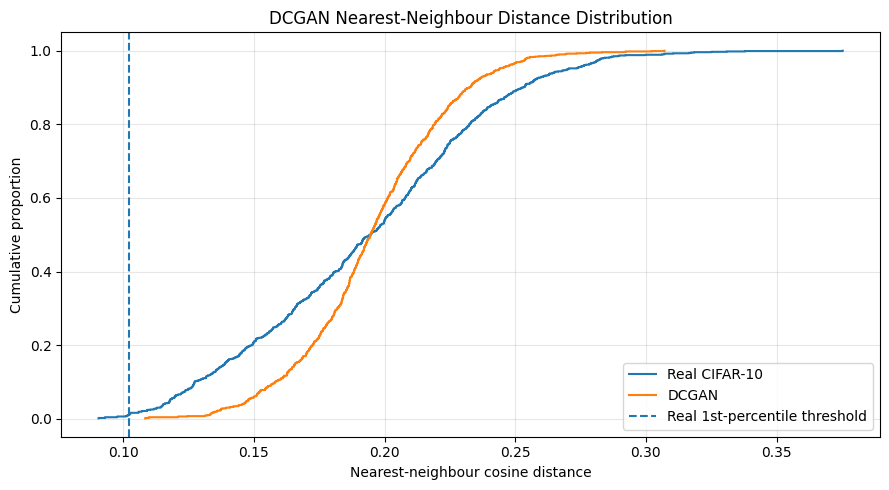

Saved nearest-distance plot: [local project directory]/grids/G02_dcgan_seed42_nearest_distance_ecdf.png


In [ ]:
dcgan_nearest_distance_plot_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_nearest_distance_ecdf.png"
)

real_sorted_distances = np.sort(
    real_nearest_distances
)

dcgan_sorted_distances = np.sort(
    dcgan_nearest_distances
)

real_ecdf = np.arange(
    1,
    len(real_sorted_distances) + 1,
) / len(real_sorted_distances)

dcgan_ecdf = np.arange(
    1,
    len(dcgan_sorted_distances) + 1,
) / len(dcgan_sorted_distances)

plt.figure(figsize=(9, 5))

plt.step(
    real_sorted_distances,
    real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    dcgan_sorted_distances,
    dcgan_ecdf,
    where="post",
    label="DCGAN",
)

plt.axvline(
    near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "DCGAN Nearest-Neighbour Distance Distribution"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    dcgan_nearest_distance_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved nearest-distance plot: "
    f"{dcgan_nearest_distance_plot_path}"
)

**Interpretation**

The nearest-neighbour distributions broadly overlap, supporting the earlier finding that DCGAN preserves substantial feature-space diversity.

The real CIFAR-10 distribution has a wider lower tail, meaning that a small proportion of real images have extremely similar neighbours. By comparison, the DCGAN curve begins farther to the right, and none of the generated nearest-neighbour distances falls below the real-data threshold of `0.102216`.

The median distances are almost identical:

```text
Real CIFAR-10: 0.194602
DCGAN:         0.194618
```

The curves differ slightly away from the median. DCGAN distances are more concentrated around the middle of the distribution, while real CIFAR-10 contains a broader range of both unusually similar and unusually dissimilar image pairs.

This suggests that DCGAN generates a varied sample without obvious repeated feature templates, although its diversity distribution does not perfectly reproduce the structure of the real dataset.

Together with the `0%` exact-duplicate rate, `0%` feature-space near-duplicate rate, and diversity ratio of `0.9324`, the plot provides no evidence of severe mode collapse in this evaluated sample.

This conclusion remains limited to generated-to-generated repetition. It does not test whether generated images copy individual training images, which remains part of the final memorisation audit in Notebook 4.

#### Most similar generated-image pairs

The ten closest DCGAN image pairs are displayed to inspect what the smallest feature-space distances represent visually.

The comparison checks whether the pairs contain:

- nearly identical images
- repeated object poses
- repeated background layouts
- similar colours and textures
- different images that happen to share broad semantic features

In [ ]:
dcgan_nearest_indices = np.argmin(
    dcgan_distance_matrix,
    axis=1,
)

unique_dcgan_pairs = {}

for image_index, neighbour_index in enumerate(
    dcgan_nearest_indices
):
    pair = tuple(
        sorted(
            (
                int(image_index),
                int(neighbour_index),
            )
        )
    )

    pair_distance = float(
        dcgan_distance_matrix[
            pair[0],
            pair[1],
        ]
    )

    if pair not in unique_dcgan_pairs:
        unique_dcgan_pairs[pair] = pair_distance

dcgan_most_similar_pairs = sorted(
    unique_dcgan_pairs.items(),
    key=lambda item: item[1],
)[:10]

dcgan_similar_pairs_path = (
    GRIDS_DIR
    / f"{DCGAN_RUN_ID}_most_similar_pairs.png"
)

fig, axes = plt.subplots(
    5,
    4,
    figsize=(10, 13),
)

for pair_number, (
    pair,
    pair_distance,
) in enumerate(dcgan_most_similar_pairs):
    row = pair_number // 2
    column = (pair_number % 2) * 2

    first_index, second_index = pair

    axes[row, column].imshow(
        dcgan_diversity_images[
            first_index
        ]
    )

    axes[row, column].set_title(
        f"Pair {pair_number + 1}A",
        fontsize=9,
    )

    axes[row, column].axis("off")

    axes[row, column + 1].imshow(
        dcgan_diversity_images[
            second_index
        ]
    )

    axes[row, column + 1].set_title(
        (
            f"Pair {pair_number + 1}B\n"
            f"Distance: {pair_distance:.4f}"
        ),
        fontsize=9,
    )

    axes[row, column + 1].axis("off")

plt.suptitle(
    "DCGAN Most Similar Generated Pairs",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    dcgan_similar_pairs_path,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved most-similar pairs figure: "
    f"{dcgan_similar_pairs_path}"
)

Saved most-similar pairs figure: [local project directory]/grids/G02_dcgan_seed42_most_similar_pairs.png


**Interpretation**

The ten closest generated-image pairs are semantically similar, but they are not near-identical copies.

Several pairs share broad object categories or scene layouts:

- Pairs 1, 4, and 6 contain car-like objects
- Pairs 2, 8, and 10 contain aircraft-like or transport-related scenes
- Pair 5 contains two horse-like images
- Pair 7 contains two vehicle-like objects
- Pair 9 contains two blurry natural or animal-like scenes

Despite these similarities, the paired images differ in colour, pose, background, viewpoint, and object shape.

The smallest generated-pair distance was `0.1084`, which remains above the real-data near-duplicate threshold of `0.102216`. This agrees with the calculated `0%` near-duplicate rate.

The figure therefore provides no evidence that DCGAN repeatedly generates almost identical images or one narrow visual template. Its closest pairs mainly share broad semantic content rather than duplicated composition.

However, the pairs also reinforce the model's main limitation. Many images are still blurry and structurally uncertain, even when they represent different modes.

The DCGAN result is therefore characterised by:

- strong feature-space diversity
- no exact duplicates
- no detected feature-space near-duplicates
- no evidence of severe mode collapse
- limited sharpness and semantic recognisability

This is a major improvement over the Dense GAN, whose closest pairs repeatedly reproduced nearly identical noisy templates.

In [ ]:
dcgan_training_time_minutes = float(
    dcgan_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

dcgan_diversity_summary = (
    f"Diversity ratio to real: "
    f"{dcgan_diversity_ratio:.4f}; "
    f"near-duplicate rate: "
    f"{dcgan_near_duplicate_rate:.1f}%; "
    f"exact duplicate rate: "
    f"{dcgan_exact_duplicate_rate:.1f}%"
)

dcgan_master_df = update_models_metrics(
    {
        "run_id": DCGAN_RUN_ID,
        "experiment_family": (
            "architecture_screen"
        ),
        "model": "DCGAN",
        "main_change": (
            "Convolutional GAN foundation"
        ),
        "seed": DCGAN_SEED,
        "epochs_completed": DCGAN_EPOCHS,
        "selected_epoch": (
            DCGAN_SELECTED_EPOCH
        ),
        "latent_dim": DCGAN_LATENT_DIM,
        "batch_size": DCGAN_BATCH_SIZE,
        "generator_parameters": (
            dcgan_generator.count_params()
        ),
        "adversary_parameters": (
            dcgan_discriminator.count_params()
        ),
        "development_fid": (
            dcgan_fid_mean
        ),
        "fid_std": dcgan_fid_std,
        "clear_count": dcgan_clear_count,
        "marginal_count": (
            dcgan_marginal_count
        ),
        "nonsense_count": (
            dcgan_nonsense_count
        ),
        "diversity_summary": (
            dcgan_diversity_summary
        ),
        "training_time_minutes": (
            dcgan_training_time_minutes
        ),
        "selected": False,
        "decision": (
            "Epoch 100 selected within the "
            "DCGAN run. Strong FID and diversity, "
            "but limited Clear recognisability and "
            "strong discriminator dominance. "
            "Architecture comparison pending."
        ),
    }
)

dcgan_master_row = dcgan_master_df.loc[
    dcgan_master_df["run_id"]
    == DCGAN_RUN_ID
]

display(dcgan_master_row)

print(
    "DCGAN results saved to "
    "models_metrics.csv."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
1,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100,64,1085187,664129,37.036681,0.299987,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,False,Epoch 100 selected within the DCGAN run. Stron...


DCGAN results saved to models_metrics.csv.


#### DCGAN findings and limitations

DCGAN completed the same 100-epoch architecture-screen process as the Dense GAN and received the full selected-checkpoint evaluation package.

##### Result summary

| Evidence | DCGAN result |
|---|---:|
| Selected checkpoint | Epoch 100 |
| Repeated development FID | `37.0367 ± 0.3000` |
| Clear | 9 out of 100 |
| Marginal | 75 out of 100 |
| Nonsense | 16 out of 100 |
| Diversity ratio to real CIFAR-10 | `0.9324` |
| Generated near-duplicate rate | `0.0%` |
| Exact duplicate rate | `0.0%` |
| Generator parameters | 1,085,187 |
| Discriminator parameters | 664,129 |
| Recorded training time | 19.47 minutes |

##### Findings

DCGAN produced a major improvement over the Dense GAN.

The convolutional generator learned substantially stronger:

- foreground-background separation
- object-sized spatial structures
- local colour organisation
- animal-like and vehicle-like forms
- variation across objects, scenes, colours, and positions

Its repeated development FID of approximately `37.0` was far lower than the Dense GAN result of approximately `327.3`, showing a much closer match to the CIFAR-10 feature distribution.

The low-level descriptor comparison also showed close alignment with real CIFAR-10 in brightness, contrast, RGB intensity, saturation, and edge strength. The generated images were slightly darker and had slightly weaker edges, which agrees with their visibly blurred boundaries.

However, semantic recognisability remained limited. Under strict manual scoring:

- only 9% were Clear
- 75% were Marginal
- 16% were Nonsense

This means that the generator often learned plausible object cues without producing sufficiently coherent geometry for confident recognition.

##### Diversity and mode collapse

DCGAN showed strong feature-space diversity:

- diversity ratio to real: `0.9324`
- feature-space near-duplicate rate: `0.0%`
- exact duplicate rate: `0.0%`

Its nearest-neighbour distance distribution broadly overlapped the real-data distribution, and the most similar generated pairs differed in pose, colour, viewpoint, background, and object shape.

There is therefore no evidence of severe mode collapse in the evaluated sample.

The main weakness is not repetition. It is the limited clarity and structural precision of many generated objects.

##### Training stability

The discriminator remained dominant throughout most of training.

By epoch 100:

| Metric | Value |
|---|---:|
| Generator loss | 5.0284 |
| Discriminator loss | 0.0649 |
| Mean real score | 0.9538 |
| Mean generated score | 0.0462 |

Despite this imbalance, FID and visual quality continued to improve. This demonstrates that GAN losses must be interpreted together with generated-image evidence rather than treated as direct quality scores.

The strong discriminator may still have restricted later generator improvement and is an important issue for the later balance and stabilisation experiments.

##### Checkpoint decision

Epoch 100 was selected because it achieved the lowest milestone FID of `36.7759` and did not show visual deterioration relative to epoch 90.

The gain over epoch 90 was small, so the model appeared to be approaching a plateau. Nevertheless, there was no multi-evidence reason to override the lowest-FID checkpoint.

##### Limitations

- Most outputs remain blurry or structurally ambiguous.
- Only 9% of the uncurated sample met the strict Clear criterion.
- The discriminator became increasingly dominant.
- Transposed-convolution generation may contribute to local blur or artifacts.
- Strong low-level descriptor alignment does not guarantee semantic recognisability.
- FID uses an ImageNet-trained feature extractor on resized CIFAR-10 images and is interpreted comparatively.
- The diversity analysis measures generated-to-generated repetition, not memorisation of training images.

##### Architecture-screen status

DCGAN is retained as a strong architecture candidate because it provides:

- substantially better FID than the Dense GAN
- much stronger spatial coherence
- close low-level descriptor alignment
- strong feature-space diversity
- no detected severe mode collapse

It is not yet marked as the selected architecture because WGAN-GP must receive the same fair 100-epoch architecture-screen opportunity.

The next question is whether WGAN-GP can improve stability, FID, recognisability, or diversity enough to justify its greater training complexity.

### 5.3 WGAN-GP

#### Question

Does WGAN-GP improve training behaviour, recognisability, diversity, or development FID enough to justify its additional training complexity?

#### Above-syllabus extension

WGAN-GP is an above-syllabus extension built directly using TensorFlow and Keras.

It still follows the assignment constraints:

- only official CIFAR-10 training images are used
- no transfer-learning generator or critic is used
- the architecture and training process are implemented and explained directly
- the same protected test-set policy remains active
- the model receives the same architecture-screen evaluation package

#### Rationale

A standard GAN discriminator predicts a probability that an image is real. When it separates real and generated images too confidently, the generator may receive weak or unstable training signals.

WGAN-GP replaces the discriminator with a **critic**.

The critic:

- outputs unrestricted scalar scores rather than probabilities
- should assign higher scores to real images than generated images
- does not use a sigmoid output
- is trained using the Wasserstein objective
- is regularised using a gradient penalty

The gradient penalty encourages the critic's gradient norm around interpolated real and generated images to remain near 1. This supports the smooth critic behaviour required by the Wasserstein formulation without weight clipping.

#### Hypothesis

WGAN-GP may provide:

- smoother and more interpretable critic behaviour
- more stable generator gradients
- stronger diversity
- less mode collapse
- improved FID or recognisability

However, it performs five critic updates for every generator update. It therefore requires substantially more computation than the earlier architectures.

Its additional complexity is justified only if the complete evaluation evidence shows a meaningful benefit.

#### Controlled settings

| Setting | Value |
|---|---:|
| Run ID | `G03_wgangp_seed42` |
| Training images | 50,000 |
| Image representation | RGB `float32` in `[-1, 1]` |
| Latent dimension | 100 |
| Batch size | 64 |
| Epoch budget | 100 |
| Training seed | 42 |
| Optimiser | Adam |
| Generator learning rate | `0.0001` |
| Critic learning rate | `0.0001` |
| Adam `beta_1` | `0.0` |
| Adam `beta_2` | `0.9` |
| Critic updates | 5 per generator update |
| Gradient-penalty coefficient | `10.0` |
| Critic normalisation | None |
| Augmentation | None |

The generator architecture is matched to the convolutional generator used in the preceding architecture screen.

The critic uses a similar convolutional channel progression, but formulation-specific differences are necessary:

- linear rather than sigmoid output
- no Batch Normalisation
- Wasserstein critic objective
- interpolated-input gradient penalty
- five critic updates per generator update
- objective-appropriate Adam settings

The later architecture comparison therefore compares complete conventional formulations rather than isolating only the loss function.

In [71]:
# WGAN-GP architecture-screen settings
WGAN_GP_RUN_ID = "G03_wgangp_seed42" 

WGAN_GP_SEED = PRIMARY_SEED 

WGAN_GP_LATENT_DIM = 100
WGAN_GP_BATCH_SIZE = 64
WGAN_GP_EPOCHS = 100

WGAN_GP_GENERATOR_LR = 1e-4
WGAN_GP_CRITIC_LR = 1e-4
WGAN_GP_BETA_1 = 0.0
WGAN_GP_BETA_2 = 0.9

WGAN_GP_CRITIC_UPDATES = 5
WGAN_GP_LAMBDA_GP = 10.0

WGAN_GP_CHECKPOINT_INTERVAL = 10
WGAN_GP_GRID_INTERVAL = 10
WGAN_GP_EVALUATION_EPOCHS = (
    50,
    70,
    90,
    100,
)

WGAN_GP_MAX_CHECKPOINTS = 3

WGAN_GP_FIXED_GRID_SIZE = 25
WGAN_GP_MANUAL_SCORE_SIZE = 100

# Persistent paths
WGAN_GP_CHECKPOINT_DIR = (
    CHECKPOINTS_DIR
    / WGAN_GP_RUN_ID
)

WGAN_GP_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{WGAN_GP_RUN_ID}.csv"
)

WGAN_GP_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{WGAN_GP_RUN_ID}_"
        "generator.weights.h5"
    )
)

WGAN_GP_SELECTED_CRITIC_PATH = (
    WEIGHTS_DIR
    / (
        f"{WGAN_GP_RUN_ID}_"
        "critic.weights.h5"
    )
)

WGAN_GP_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Run ID:          {WGAN_GP_RUN_ID}")
print(f"Checkpoint path: {WGAN_GP_CHECKPOINT_DIR}")
print(f"History path:    {WGAN_GP_HISTORY_PATH}")
print(f"Epoch budget:    {WGAN_GP_EPOCHS}")
print(f"Batch size:      {WGAN_GP_BATCH_SIZE}")
print(f"Latent dim:      {WGAN_GP_LATENT_DIM}")
print(
    f"Update ratio:    "
    f"{WGAN_GP_CRITIC_UPDATES}C:1G"
)
print(
    f"Gradient penalty coefficient: "
    f"{WGAN_GP_LAMBDA_GP}"
)

Run ID:          G03_wgangp_seed42
Checkpoint path: [local project directory]/checkpoints/G03_wgangp_seed42
History path:    [local project directory]/histories/G03_wgangp_seed42.csv
Epoch budget:    100
Batch size:      64
Latent dim:      100
Update ratio:    5C:1G
Gradient penalty coefficient: 10.0


#### Architecture design

##### Generator

```text
Latent vector, 100
→ Dense 4 × 4 × 256
→ Batch Normalisation
→ LeakyReLU
→ Reshape to 4 × 4 × 256
→ Conv2DTranspose 128, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Conv2DTranspose 64, stride 2
→ Batch Normalisation
→ LeakyReLU
→ Conv2DTranspose 3, stride 2
→ tanh
→ Output 32 × 32 × 3
```

The generator is architecturally matched to the earlier convolutional generator.

Its spatial progression remains:

```text
4 × 4 → 8 × 8 → 16 × 16 → 32 × 32
```

This holds the generator representation approximately constant while the adversarial formulation changes.

##### Critic

```text
Input 32 × 32 × 3
→ Conv2D 64, stride 2
→ LeakyReLU
→ Conv2D 128, stride 2
→ LeakyReLU
→ Conv2D 256, stride 2
→ LeakyReLU
→ Flatten
→ Dense 1
→ unrestricted scalar score
```

The critic progressively reduces spatial resolution:

```text
32 × 32 → 16 × 16 → 8 × 8 → 4 × 4
```

The critic does not use:

- a sigmoid output
- binary cross-entropy
- Batch Normalisation
- dropout
- weight clipping

Batch Normalisation is omitted because its batch-dependent behaviour is inappropriate for the per-example gradient constraint used by WGAN-GP.

The initial architecture-screen critic uses no normalisation. A targeted Layer Normalisation comparison remains available later only if critic gradients or score behaviour show instability.

In [72]:
# Build the WGAN-GP generator.
def build_wgan_gp_generator(latent_dim):

    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.Conv2DTranspose(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                3,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="WGAN_GP_Generator",
    )

    return model

In [73]:
# Build the WGAN-GP critic.
def build_wgan_gp_critic():

    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                kernel_initializer=weight_init,
            ),
        ],
        name="WGAN_GP_Critic",
    )

    return model

In [74]:
keras.backend.clear_session()
keras.utils.set_random_seed(
    WGAN_GP_SEED
)

wgan_gp_generator = (
    build_wgan_gp_generator(
        WGAN_GP_LATENT_DIM
    )
)

wgan_gp_critic = (
    build_wgan_gp_critic()
)

print("WGAN-GP generator")
wgan_gp_generator.summary()

print("\nWGAN-GP critic")
wgan_gp_critic.summary()

print("\nParameter counts")

print(
    f"Generator: "
    f"{wgan_gp_generator.count_params():,}"
)

print(
    f"Critic:    "
    f"{wgan_gp_critic.count_params():,}"
)

WGAN-GP generator


Model: "WGAN_GP_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,187 (4.14 MB)

 Trainable params: 1,076,611 (4.11 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,977 (2.53 MB)

 Trainable params: 662,977 (2.53 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts
Generator: 1,085,187
Critic:    662,977


In [75]:
wgan_gp_test_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

wgan_gp_test_images = (
    wgan_gp_generator(
        wgan_gp_test_noise,
        training=False,
    )
)

wgan_gp_test_scores = (
    wgan_gp_critic(
        wgan_gp_test_images,
        training=False,
    )
)

print("Generated image batch")
print(
    f"Shape: "
    f"{wgan_gp_test_images.shape}"
)
print(
    f"Dtype: "
    f"{wgan_gp_test_images.dtype}"
)

print(
    "Range: "
    f"[{tf.reduce_min(wgan_gp_test_images).numpy():.4f}, "
    f"{tf.reduce_max(wgan_gp_test_images).numpy():.4f}]"
)

print("\nCritic output")
print(
    f"Shape: "
    f"{wgan_gp_test_scores.shape}"
)

print(
    "Range: "
    f"[{tf.reduce_min(wgan_gp_test_scores).numpy():.4f}, "
    f"{tf.reduce_max(wgan_gp_test_scores).numpy():.4f}]"
)

assert wgan_gp_test_images.shape == (
    8,
    32,
    32,
    3,
)

assert (
    wgan_gp_test_images.dtype
    == tf.float32
)

assert (
    tf.reduce_min(
        wgan_gp_test_images
    ).numpy()
    >= -1.0
)

assert (
    tf.reduce_max(
        wgan_gp_test_images
    ).numpy()
    <= 1.0
)

assert wgan_gp_test_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    wgan_gp_test_scores.numpy()
).all()

assert not any(
    isinstance(
        layer,
        layers.BatchNormalization,
    )
    for layer in wgan_gp_critic.layers
)

assert (
    wgan_gp_critic.layers[-1].activation
    == keras.activations.linear
)

del wgan_gp_test_noise
del wgan_gp_test_images
del wgan_gp_test_scores

print(
    "\nWGAN-GP architecture "
    "validation passed."
)

print(
    "Critic contains no "
    "Batch Normalisation."
)

print(
    "Critic output is linear "
    "and unrestricted."
)

Generated image batch
Shape: (8, 32, 32, 3)
Dtype: <dtype: 'float32'>
Range: [-0.0300, 0.0304]

Critic output
Shape: (8, 1)
Range: [-0.0005, -0.0001]

WGAN-GP architecture validation passed.
Critic contains no Batch Normalisation.
Critic output is linear and unrestricted.


#### Wasserstein objective and gradient penalty

WGAN-GP does not use binary classification labels.

The critic objective is:

```text
critic loss
= mean generated score
- mean real score
+ lambda × gradient penalty
```

Minimising this objective encourages:

- higher scores for real images
- lower scores for generated images
- gradient norms near 1 around interpolated images

The generator objective is:

```text
generator loss
= -mean generated score
```

Minimising this objective encourages the generator to produce images that receive higher critic scores.

The gradient penalty is calculated using interpolated images:

```text
interpolated image
= alpha × real image
+ (1 - alpha) × generated image
```

where `alpha` is sampled independently between 0 and 1.

The penalty is:

```text
gradient penalty
= mean((gradient norm - 1)²)
```

The gradients must be taken with respect to the interpolated input images, not the critic weights.

##### Update ratio

Each training batch performs:

```text
5 critic updates
→ 1 generator update
```

With 782 batches per epoch, this produces:

```text
3,910 critic optimiser updates per epoch
782 generator optimiser updates per epoch
```

The greater critic exposure is part of the conventional WGAN-GP formulation and will be considered when comparing training time and implementation complexity.

In [76]:
wgan_gp_generator_optimizer = (
    optimizers.Adam(
        learning_rate=(
            WGAN_GP_GENERATOR_LR
        ),
        beta_1=WGAN_GP_BETA_1,
        beta_2=WGAN_GP_BETA_2,
    )
)

wgan_gp_critic_optimizer = (
    optimizers.Adam(
        learning_rate=(
            WGAN_GP_CRITIC_LR
        ),
        beta_1=WGAN_GP_BETA_1,
        beta_2=WGAN_GP_BETA_2,
    )
)

# Create optimiser variables before
# checkpoint restoration.
wgan_gp_generator_optimizer.build(
    wgan_gp_generator.trainable_variables
)

wgan_gp_critic_optimizer.build(
    wgan_gp_critic.trainable_variables
)

print(
    "WGAN-GP optimisers created."
)

print(
    f"Generator learning rate: "
    f"{WGAN_GP_GENERATOR_LR}"
)

print(
    f"Critic learning rate:    "
    f"{WGAN_GP_CRITIC_LR}"
)

print(
    f"Adam beta values:        "
    f"({WGAN_GP_BETA_1}, "
    f"{WGAN_GP_BETA_2})"
)

WGAN-GP optimisers created.
Generator learning rate: 0.0001
Critic learning rate:    0.0001
Adam beta values:        (0.0, 0.9)


In [77]:
wgan_gp_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=WGAN_GP_BATCH_SIZE,
        seed=WGAN_GP_SEED,
    )
)

wgan_gp_fixed_noise = (
    make_stateless_noise(
        sample_count=(
            WGAN_GP_FIXED_GRID_SIZE
        ),
        latent_dim=(
            WGAN_GP_LATENT_DIM
        ),
        seed=FIXED_LATENT_SEED,
    )
)

wgan_gp_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        wgan_gp_train_dataset
    ).numpy()
)

wgan_gp_critic_updates_per_epoch = (
    wgan_gp_batches_per_epoch
    * WGAN_GP_CRITIC_UPDATES
)

wgan_gp_generator_updates_per_epoch = (
    wgan_gp_batches_per_epoch
)

print(
    f"Batches per epoch: "
    f"{wgan_gp_batches_per_epoch}"
)

print(
    f"Fixed grid noise: "
    f"{wgan_gp_fixed_noise.shape}"
)

print(
    f"Critic updates per epoch: "
    f"{wgan_gp_critic_updates_per_epoch:,}"
)

print(
    f"Generator updates per epoch: "
    f"{wgan_gp_generator_updates_per_epoch:,}"
)

assert (
    wgan_gp_batches_per_epoch
    == 782
)

assert wgan_gp_fixed_noise.shape == (
    25,
    100,
)

assert (
    wgan_gp_critic_updates_per_epoch
    == 3_910
)

assert (
    wgan_gp_generator_updates_per_epoch
    == 782
)

Batches per epoch: 782
Fixed grid noise: (25, 100)
Critic updates per epoch: 3,910
Generator updates per epoch: 782


In [78]:
# Calculate WGAN-GP's interpolated-input
# gradient penalty.
def calculate_wgan_gp_penalty(
    critic,
    real_images,
    generated_images,
):

    batch_size = tf.shape(
        real_images
    )[0]

    alpha = tf.random.uniform(
        shape=(
            batch_size,
            1,
            1,
            1,
        ),
        minval=0.0,
        maxval=1.0,
        dtype=tf.float32,
    )

    interpolated_images = (
        alpha * real_images
        + (1.0 - alpha)
        * generated_images
    )

    with tf.GradientTape() as penalty_tape:
        penalty_tape.watch(
            interpolated_images
        )

        interpolated_scores = critic(
            interpolated_images,
            training=True,
        )

    input_gradients = penalty_tape.gradient(
        interpolated_scores,
        interpolated_images,
    )

    gradient_norms = tf.sqrt(
        tf.reduce_sum(
            tf.square(input_gradients),
            axis=[1, 2, 3],
        )
        + 1e-12
    )

    gradient_penalty = tf.reduce_mean(
        tf.square(
            gradient_norms - 1.0
        )
    )

    return (
        gradient_penalty,
        gradient_norms,
    )

#### One-batch WGAN-GP validation

Before the formal run begins, one training batch is used to verify the WGAN-GP objective without applying any optimiser updates.

The validation checks:

- finite real and generated critic scores
- finite, non-negative gradient penalty
- finite per-example gradient norms
- critic gradients connected to all critic variables
- generator gradients connected to all generator variables
- correct gradient calculation with respect to interpolated images

This validation does not modify the formal model weights or optimiser states.

In [79]:
wgan_gp_validation_real_images = next(
    iter(wgan_gp_train_dataset)
)[:8]

wgan_gp_validation_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=WGAN_GP_LATENT_DIM,
        seed=SECONDARY_SEED,
    )
)

wgan_gp_validation_fake_images = (
    wgan_gp_generator(
        wgan_gp_validation_noise,
        training=False,
    )
)

# Validate critic objective and gradients.
with tf.GradientTape() as critic_tape:
    validation_real_scores = (
        wgan_gp_critic(
            wgan_gp_validation_real_images,
            training=False,
        )
    )

    validation_fake_scores = (
        wgan_gp_critic(
            tf.stop_gradient(
                wgan_gp_validation_fake_images
            ),
            training=False,
        )
    )

    (
        validation_gradient_penalty,
        validation_gradient_norms,
    ) = calculate_wgan_gp_penalty(
        critic=wgan_gp_critic,
        real_images=(
            wgan_gp_validation_real_images
        ),
        generated_images=(
            tf.stop_gradient(
                wgan_gp_validation_fake_images
            )
        ),
    )

    validation_critic_loss = (
        tf.reduce_mean(
            validation_fake_scores
        )
        - tf.reduce_mean(
            validation_real_scores
        )
        + WGAN_GP_LAMBDA_GP
        * validation_gradient_penalty
    )

validation_critic_gradients = (
    critic_tape.gradient(
        validation_critic_loss,
        wgan_gp_critic.trainable_variables,
    )
)

# Validate generator objective and gradients.
with tf.GradientTape() as generator_tape:
    validation_generated_images = (
        wgan_gp_generator(
            wgan_gp_validation_noise,
            training=False,
        )
    )

    validation_generated_scores = (
        wgan_gp_critic(
            validation_generated_images,
            training=False,
        )
    )

    validation_generator_loss = (
        -tf.reduce_mean(
            validation_generated_scores
        )
    )

validation_generator_gradients = (
    generator_tape.gradient(
        validation_generator_loss,
        wgan_gp_generator
        .trainable_variables,
    )
)

assert np.isfinite(
    validation_real_scores.numpy()
).all()

assert np.isfinite(
    validation_fake_scores.numpy()
).all()

assert np.isfinite(
    validation_gradient_penalty.numpy()
)

assert (
    validation_gradient_penalty.numpy()
    >= 0.0
)

assert np.isfinite(
    validation_gradient_norms.numpy()
).all()

assert (
    validation_gradient_norms.numpy()
    > 0.0
).all()

assert all(
    gradient is not None
    for gradient
    in validation_critic_gradients
)

assert all(
    gradient is not None
    for gradient
    in validation_generator_gradients
)

assert all(
    np.isfinite(
        gradient.numpy()
    ).all()
    for gradient
    in validation_critic_gradients
)

assert all(
    np.isfinite(
        gradient.numpy()
    ).all()
    for gradient
    in validation_generator_gradients
)

print(
    "WGAN-GP one-batch "
    "validation passed."
)

print(
    f"Real score mean:       "
    f"{tf.reduce_mean(validation_real_scores).numpy():.6f}"
)

print(
    f"Generated score mean:  "
    f"{tf.reduce_mean(validation_fake_scores).numpy():.6f}"
)

print(
    f"Critic loss:           "
    f"{validation_critic_loss.numpy():.6f}"
)

print(
    f"Generator loss:        "
    f"{validation_generator_loss.numpy():.6f}"
)

print(
    f"Gradient penalty:      "
    f"{validation_gradient_penalty.numpy():.6f}"
)

print(
    f"Mean gradient norm:    "
    f"{tf.reduce_mean(validation_gradient_norms).numpy():.6f}"
)

print(
    f"Minimum gradient norm: "
    f"{tf.reduce_min(validation_gradient_norms).numpy():.6f}"
)

print(
    f"Maximum gradient norm: "
    f"{tf.reduce_max(validation_gradient_norms).numpy():.6f}"
)

del wgan_gp_validation_real_images
del wgan_gp_validation_noise
del wgan_gp_validation_fake_images
del validation_real_scores
del validation_fake_scores
del validation_gradient_penalty
del validation_gradient_norms
del validation_critic_loss
del validation_generated_images
del validation_generated_scores
del validation_generator_loss
del validation_critic_gradients
del validation_generator_gradients

WGAN-GP one-batch validation passed.
Real score mean:       0.001668
Generated score mean:  -0.000219
Critic loss:           9.316266
Generator loss:        0.000219
Gradient penalty:      0.931815
Mean gradient norm:    0.034695
Minimum gradient norm: 0.032144
Maximum gradient norm: 0.036131


#### Saved training artifacts

The WGAN-GP run follows the same persistence contract as the earlier architecture runs.

##### After every completed epoch

```text
histories/G03_wgangp_seed42.csv
```

The history records:

- generator loss
- critic loss
- mean real critic score
- mean generated critic score
- gradient penalty
- epoch training time

##### Every 10 epochs and at the final epoch

```text
checkpoints/G03_wgangp_seed42/
grids/G03_wgangp_seed42_epoch010.png
...
grids/G03_wgangp_seed42_epoch100.png
```

Each full checkpoint contains:

- generator
- critic
- both optimisers
- completed epoch counter

##### Formal evaluation milestones

Matching generator and critic weights are saved at epochs 50, 70, 90, and 100:

```text
weights/G03_wgangp_seed42_epoch050_generator.weights.h5
weights/G03_wgangp_seed42_epoch050_critic.weights.h5
```

This ensures that any selected milestone remains reloadable even after older full checkpoints are pruned.

In [80]:
wgan_gp_completed_epoch = tf.Variable(
    0,
    dtype=tf.int64,
    trainable=False,
    name="completed_epoch",
)

wgan_gp_checkpoint = tf.train.Checkpoint(
    epoch=wgan_gp_completed_epoch,
    generator=wgan_gp_generator,
    critic=wgan_gp_critic,
    generator_optimizer=(
        wgan_gp_generator_optimizer
    ),
    critic_optimizer=(
        wgan_gp_critic_optimizer
    ),
)

wgan_gp_checkpoint_manager = (
    tf.train.CheckpointManager(
        checkpoint=wgan_gp_checkpoint,
        directory=str(
            WGAN_GP_CHECKPOINT_DIR
        ),
        max_to_keep=(
            WGAN_GP_MAX_CHECKPOINTS
        ),
    )
)

if (
    wgan_gp_checkpoint_manager
    .latest_checkpoint
):
    wgan_gp_checkpoint.restore(
        wgan_gp_checkpoint_manager
        .latest_checkpoint
    )

    print(
        "Restored checkpoint: "
        f"{wgan_gp_checkpoint_manager.latest_checkpoint}"
    )

    print(
        "Restored completed epoch: "
        f"{int(wgan_gp_completed_epoch.numpy())}"
    )

else:
    print(
        "No existing checkpoint found."
    )

    print(
        "WGAN-GP will begin "
        "from epoch 1."
    )

No existing checkpoint found.
WGAN-GP will begin from epoch 1.


In [81]:
wgan_gp_history = load_and_align_history(
    history_path=WGAN_GP_HISTORY_PATH,
    columns=WGAN_GP_HISTORY_COLUMNS,
    restored_epoch=int(
        wgan_gp_completed_epoch.numpy()
    ),
)

print(
    f"History rows available: "
    f"{len(wgan_gp_history)}"
)

if not wgan_gp_history.empty:
    print(
        f"Latest history epoch: "
        f"{int(wgan_gp_history['epoch'].max())}"
    )

History rows available: 0


#### Alternating WGAN-GP updates

Each training batch performs five critic updates followed by one generator update.

##### Critic updates

For each critic update:

1. Generate a new fake image batch using generator training behaviour.
2. Stop gradients from flowing into the generator.
3. Calculate real and generated critic scores.
4. Create random interpolations between real and generated images.
5. Calculate the critic gradient with respect to the interpolated images.
6. Calculate the gradient penalty.
7. Update only the critic variables.

The critic loss combines:

- the generated score
- the negative real score
- the weighted gradient penalty

##### Generator update

After five critic updates:

1. Generate a new fake image batch using generator training behaviour.
2. Pass the generated images through the critic.
3. Negate the mean generated critic score.
4. Update only the generator variables.

The critic remains part of the forward calculation, but its variables are not optimised during the generator update.

The generator uses `training=True` during both critic and generator phases so that both objectives observe generated images produced with the same Batch Normalisation behaviour. During critic updates, `tf.stop_gradient` prevents the critic loss from updating the generator's trainable parameters, although its Batch Normalisation moving statistics may still update during the forward pass.

In [82]:
@tf.function
def wgan_gp_train_step(real_images):

    current_batch_size = tf.shape(
        real_images
    )[0]

    critic_loss_total = tf.constant(
        0.0,
        dtype=tf.float32,
    )

    real_score_total = tf.constant(
        0.0,
        dtype=tf.float32,
    )

    fake_score_total = tf.constant(
        0.0,
        dtype=tf.float32,
    )

    gradient_penalty_total = tf.constant(
        0.0,
        dtype=tf.float32,
    )

    # 1. Update the critic
    for _ in range(
        WGAN_GP_CRITIC_UPDATES
    ):
        critic_noise = tf.random.normal(
            shape=(
                current_batch_size,
                WGAN_GP_LATENT_DIM,
            )
        )

        fake_images_for_critic = (
            wgan_gp_generator(
                critic_noise,
                training=True,
            )
        )

        fake_images_for_critic = (
            tf.stop_gradient(
                fake_images_for_critic
            )
        )

        with tf.GradientTape() as critic_tape:
            real_scores = wgan_gp_critic(
                real_images,
                training=True,
            )

            fake_scores = wgan_gp_critic(
                fake_images_for_critic,
                training=True,
            )

            (
                gradient_penalty,
                gradient_norms,
            ) = calculate_wgan_gp_penalty(
                critic=wgan_gp_critic,
                real_images=real_images,
                generated_images=(
                    fake_images_for_critic
                ),
            )

            critic_loss = (
                tf.reduce_mean(
                    fake_scores
                )
                - tf.reduce_mean(
                    real_scores
                )
                + WGAN_GP_LAMBDA_GP
                * gradient_penalty
            )

        critic_gradients = (
            critic_tape.gradient(
                critic_loss,
                wgan_gp_critic
                .trainable_variables,
            )
        )

        wgan_gp_critic_optimizer.apply_gradients(
            zip(
                critic_gradients,
                wgan_gp_critic
                .trainable_variables,
            )
        )

        critic_loss_total += critic_loss

        real_score_total += tf.reduce_mean(
            real_scores
        )

        fake_score_total += tf.reduce_mean(
            fake_scores
        )

        gradient_penalty_total += (
            gradient_penalty
        )

    critic_update_count = tf.cast(
        WGAN_GP_CRITIC_UPDATES,
        tf.float32,
    )

    mean_critic_loss = (
        critic_loss_total
        / critic_update_count
    )

    mean_real_score = (
        real_score_total
        / critic_update_count
    )

    mean_fake_score = (
        fake_score_total
        / critic_update_count
    )

    mean_gradient_penalty = (
        gradient_penalty_total
        / critic_update_count
    )

    # 2. Update the generator
    generator_noise = tf.random.normal(
        shape=(
            current_batch_size,
            WGAN_GP_LATENT_DIM,
        )
    )

    with tf.GradientTape() as generator_tape:
        generated_images = (
            wgan_gp_generator(
                generator_noise,
                training=True,
            )
        )

        generated_scores = (
            wgan_gp_critic(
                generated_images,
                training=True,
            )
        )

        generator_loss = (
            -tf.reduce_mean(
                generated_scores
            )
        )

    generator_gradients = (
        generator_tape.gradient(
            generator_loss,
            wgan_gp_generator
            .trainable_variables,
        )
    )

    wgan_gp_generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            wgan_gp_generator
            .trainable_variables,
        )
    )

    return {
        "generator_loss": generator_loss,
        "critic_loss": mean_critic_loss,
        "real_score": mean_real_score,
        "fake_score": mean_fake_score,
        "gradient_penalty": (
            mean_gradient_penalty
        ),
    }

In [83]:
# Save the current WGAN-GP checkpoint
# and fixed-seed grid.
def save_wgan_gp_state(epoch):

    checkpoint_path = (
        wgan_gp_checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        GRIDS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    save_generated_grid(
        generator=wgan_gp_generator,
        noise=wgan_gp_fixed_noise,
        save_path=grid_path,
        title=(
            f"WGAN-GP, Epoch {epoch}"
        ),
    )

    print(
        f"Saved checkpoint: "
        f"{checkpoint_path}"
    )

    print(
        f"Saved grid:       "
        f"{grid_path}"
    )

In [84]:
# Train or resume WGAN-GP to the
# requested epoch.
def train_wgan_gp(target_epochs):

    start_epoch = (
        int(
            wgan_gp_completed_epoch.numpy()
        )
        + 1
    )

    if start_epoch > target_epochs:
        print(
            "WGAN-GP is already trained "
            f"through epoch "
            f"{int(wgan_gp_completed_epoch.numpy())}."
        )

        return load_and_align_history(
            history_path=(
                WGAN_GP_HISTORY_PATH
            ),
            columns=(
                WGAN_GP_HISTORY_COLUMNS
            ),
            restored_epoch=int(
                wgan_gp_completed_epoch.numpy()
            ),
        )

    print(
        f"Training WGAN-GP from epoch "
        f"{start_epoch} to {target_epochs}."
    )

    print(
        f"Critic updates per epoch: "
        f"{wgan_gp_critic_updates_per_epoch:,}"
    )

    print(
        f"Generator updates per epoch: "
        f"{wgan_gp_generator_updates_per_epoch:,}"
    )

    for epoch in range(
        start_epoch,
        target_epochs + 1,
    ):
        epoch_start_time = time.time()

        generator_loss_mean = (
            keras.metrics.Mean()
        )

        critic_loss_mean = (
            keras.metrics.Mean()
        )

        real_score_mean = (
            keras.metrics.Mean()
        )

        fake_score_mean = (
            keras.metrics.Mean()
        )

        gradient_penalty_mean = (
            keras.metrics.Mean()
        )

        for real_images in (
            wgan_gp_train_dataset
        ):
            batch_results = (
                wgan_gp_train_step(
                    real_images
                )
            )

            generator_loss_mean.update_state(
                batch_results[
                    "generator_loss"
                ]
            )

            critic_loss_mean.update_state(
                batch_results[
                    "critic_loss"
                ]
            )

            real_score_mean.update_state(
                batch_results[
                    "real_score"
                ]
            )

            fake_score_mean.update_state(
                batch_results[
                    "fake_score"
                ]
            )

            gradient_penalty_mean.update_state(
                batch_results[
                    "gradient_penalty"
                ]
            )

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        epoch_results = {
            "epoch": epoch,
            "generator_loss": float(
                generator_loss_mean
                .result()
                .numpy()
            ),
            "critic_loss": float(
                critic_loss_mean
                .result()
                .numpy()
            ),
            "real_score": float(
                real_score_mean
                .result()
                .numpy()
            ),
            "fake_score": float(
                fake_score_mean
                .result()
                .numpy()
            ),
            "gradient_penalty": float(
                gradient_penalty_mean
                .result()
                .numpy()
            ),
            "epoch_time_seconds": float(
                epoch_time
            ),
        }

        numeric_results = np.array(
            [
                epoch_results[
                    "generator_loss"
                ],
                epoch_results[
                    "critic_loss"
                ],
                epoch_results[
                    "real_score"
                ],
                epoch_results[
                    "fake_score"
                ],
                epoch_results[
                    "gradient_penalty"
                ],
                epoch_results[
                    "epoch_time_seconds"
                ],
            ]
        )

        if not np.isfinite(
            numeric_results
        ).all():
            raise FloatingPointError(
                "Non-finite WGAN-GP "
                "training value detected "
                f"at epoch {epoch}."
            )

        wgan_gp_completed_epoch.assign(
            epoch
        )

        # Save history after every epoch.
        wgan_gp_history = (
            save_epoch_history(
                history_path=(
                    WGAN_GP_HISTORY_PATH
                ),
                row=epoch_results,
                columns=(
                    WGAN_GP_HISTORY_COLUMNS
                ),
            )
        )

        # Save matching milestone weights.
        if (
            epoch
            in WGAN_GP_EVALUATION_EPOCHS
        ):
            milestone_generator_path = (
                WEIGHTS_DIR
                / (
                    f"{WGAN_GP_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            milestone_critic_path = (
                WEIGHTS_DIR
                / (
                    f"{WGAN_GP_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "critic.weights.h5"
                )
            )

            wgan_gp_generator.save_weights(
                milestone_generator_path
            )

            wgan_gp_critic.save_weights(
                milestone_critic_path
            )

            print(
                "Saved milestone generator: "
                f"{milestone_generator_path}"
            )

            print(
                "Saved milestone critic:    "
                f"{milestone_critic_path}"
            )

        # Save checkpoint and grid.
        if (
            epoch
            % WGAN_GP_CHECKPOINT_INTERVAL
            == 0
            or epoch == target_epochs
        ):
            save_wgan_gp_state(
                epoch=epoch
            )

        score_gap = (
            epoch_results["real_score"]
            - epoch_results["fake_score"]
        )

        print(
            f"Epoch {epoch:03d}/{target_epochs} "
            f"| G loss: "
            f"{epoch_results['generator_loss']:.4f} "
            f"| C loss: "
            f"{epoch_results['critic_loss']:.4f} "
            f"| Real: "
            f"{epoch_results['real_score']:.4f} "
            f"| Fake: "
            f"{epoch_results['fake_score']:.4f} "
            f"| Gap: "
            f"{score_gap:.4f} "
            f"| GP: "
            f"{epoch_results['gradient_penalty']:.4f} "
            f"| Time: "
            f"{epoch_results['epoch_time_seconds']:.1f}s"
        )

    total_training_minutes = float(
        wgan_gp_history[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    update_models_metrics(
        {
            "run_id": WGAN_GP_RUN_ID,
            "experiment_family": (
                "architecture_screen"
            ),
            "model": "WGAN-GP",
            "main_change": (
                "Wasserstein objective "
                "with gradient penalty"
            ),
            "seed": WGAN_GP_SEED,
            "epochs_completed": int(
                wgan_gp_completed_epoch.numpy()
            ),
            "latent_dim": (
                WGAN_GP_LATENT_DIM
            ),
            "batch_size": (
                WGAN_GP_BATCH_SIZE
            ),
            "generator_parameters": (
                wgan_gp_generator.count_params()
            ),
            "adversary_parameters": (
                wgan_gp_critic.count_params()
            ),
            "training_time_minutes": (
                total_training_minutes
            ),
        }
    )

    print(
        "\nWGAN-GP training complete."
    )

    print(
        f"Completed epoch: "
        f"{int(wgan_gp_completed_epoch.numpy())}"
    )

    print(
        f"Total recorded training time: "
        f"{total_training_minutes:.2f} minutes"
    )

    return wgan_gp_history

**Pre-training interpretation**

The initial critic produced unrestricted scores close to zero, which is expected before training.

The mean interpolated-input gradient norm was `0.034706`, substantially below the WGAN-GP target of 1. This produced a gradient penalty of `0.931794`, which dominated the initial critic loss.

This is expected for a randomly initialised critic. The gradient penalty exists specifically to move these input-gradient norms toward 1 during training.

The result does not currently justify critic normalisation. Layer Normalisation will be considered only if several early-training signals agree that the critic remains unstable, such as:

- persistently abnormal gradient-penalty behaviour
- diverging real and generated scores
- non-finite values
- poor fixed-grid progression
- worsening FID

#### Static-adversary update validation

For the WGAN-GP implementation, the generator is called with `training=True` during both critic and generator phases. This ensures that generated images use the same Batch Normalisation behaviour in both objectives.

During a critic update:

- critic trainable parameters may change
- generator trainable parameters must not change
- generator BatchNorm moving statistics may update during the training-mode forward pass
- `tf.stop_gradient` prevents critic-loss gradients from updating the generator

During a generator update:

- generator trainable parameters may change
- generator BatchNorm moving statistics may update
- critic trainable parameters must not change

Therefore, “static generator” refers specifically to the absence of gradient-based updates to its trainable parameters during the critic phase. The validation below checks trainable parameters and BatchNorm state separately.

In [85]:
# Return the largest absolute variable change.
def maximum_weight_change(
    values_before,
    variables_after,
):

    return max(
        float(
            np.max(
                np.abs(
                    before
                    - after.numpy()
                )
            )
        )
        for before, after in zip(
            values_before,
            variables_after,
        )
    )


# Build temporary models for validation.
check_generator = build_wgan_gp_generator(
    WGAN_GP_LATENT_DIM
)

check_critic = build_wgan_gp_critic()

check_generator.set_weights(
    wgan_gp_generator.get_weights()
)

check_critic.set_weights(
    wgan_gp_critic.get_weights()
)

check_generator_optimizer = optimizers.Adam(
    learning_rate=WGAN_GP_GENERATOR_LR,
    beta_1=WGAN_GP_BETA_1,
    beta_2=WGAN_GP_BETA_2,
)

check_critic_optimizer = optimizers.Adam(
    learning_rate=WGAN_GP_CRITIC_LR,
    beta_1=WGAN_GP_BETA_1,
    beta_2=WGAN_GP_BETA_2,
)

check_generator_optimizer.build(
    check_generator.trainable_variables
)

check_critic_optimizer.build(
    check_critic.trainable_variables
)

check_real_images = next(
    iter(wgan_gp_train_dataset)
)[:8]


# 1. Critic update

critic_check_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=7001,
)

generator_trainable_before_critic = [
    variable.numpy().copy()
    for variable
    in check_generator.trainable_variables
]

generator_state_before_critic = [
    variable.numpy().copy()
    for variable
    in check_generator.non_trainable_variables
]

critic_trainable_before_critic = [
    variable.numpy().copy()
    for variable
    in check_critic.trainable_variables
]

# Match the corrected formal training step.
critic_check_fake_images = check_generator(
    critic_check_noise,
    training=True,
)

critic_check_fake_images = tf.stop_gradient(
    critic_check_fake_images
)

with tf.GradientTape() as critic_tape:

    critic_check_real_scores = check_critic(
        check_real_images,
        training=True,
    )

    critic_check_fake_scores = check_critic(
        critic_check_fake_images,
        training=True,
    )

    (
        critic_check_penalty,
        critic_check_gradient_norms,
    ) = calculate_wgan_gp_penalty(
        critic=check_critic,
        real_images=check_real_images,
        generated_images=(
            critic_check_fake_images
        ),
    )

    critic_check_loss = (
        tf.reduce_mean(
            critic_check_fake_scores
        )
        - tf.reduce_mean(
            critic_check_real_scores
        )
        + WGAN_GP_LAMBDA_GP
        * critic_check_penalty
    )

critic_check_gradients = critic_tape.gradient(
    critic_check_loss,
    check_critic.trainable_variables,
)

check_critic_optimizer.apply_gradients(
    zip(
        critic_check_gradients,
        check_critic.trainable_variables,
    )
)

critic_trainable_change = (
    maximum_weight_change(
        critic_trainable_before_critic,
        check_critic.trainable_variables,
    )
)

generator_trainable_change_during_critic = (
    maximum_weight_change(
        generator_trainable_before_critic,
        check_generator.trainable_variables,
    )
)

generator_state_change_during_critic = (
    maximum_weight_change(
        generator_state_before_critic,
        check_generator.non_trainable_variables,
    )
)


# 2. Generator update

generator_trainable_before_generator = [
    variable.numpy().copy()
    for variable
    in check_generator.trainable_variables
]

generator_state_before_generator = [
    variable.numpy().copy()
    for variable
    in check_generator.non_trainable_variables
]

critic_trainable_before_generator = [
    variable.numpy().copy()
    for variable
    in check_critic.trainable_variables
]

generator_check_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=7002,
)

with tf.GradientTape() as generator_tape:

    generator_check_images = check_generator(
        generator_check_noise,
        training=True,
    )

    generator_check_scores = check_critic(
        generator_check_images,
        training=True,
    )

    generator_check_loss = (
        -tf.reduce_mean(
            generator_check_scores
        )
    )

generator_check_gradients = (
    generator_tape.gradient(
        generator_check_loss,
        check_generator.trainable_variables,
    )
)

check_generator_optimizer.apply_gradients(
    zip(
        generator_check_gradients,
        check_generator.trainable_variables,
    )
)

generator_trainable_change = (
    maximum_weight_change(
        generator_trainable_before_generator,
        check_generator.trainable_variables,
    )
)

generator_state_change_during_generator = (
    maximum_weight_change(
        generator_state_before_generator,
        check_generator.non_trainable_variables,
    )
)

critic_trainable_change_during_generator = (
    maximum_weight_change(
        critic_trainable_before_generator,
        check_critic.trainable_variables,
    )
)


# 3. Gradient-penalty response

penalty_noise_1 = make_stateless_noise(
    sample_count=8,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=7003,
)

penalty_noise_2 = make_stateless_noise(
    sample_count=8,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=7004,
)

penalty_fake_images_1 = check_generator(
    penalty_noise_1,
    training=False,
)

penalty_fake_images_2 = check_generator(
    penalty_noise_2,
    training=False,
)

penalty_value_1, _ = calculate_wgan_gp_penalty(
    critic=check_critic,
    real_images=check_real_images,
    generated_images=penalty_fake_images_1,
)

penalty_value_2, _ = calculate_wgan_gp_penalty(
    critic=check_critic,
    real_images=check_real_images,
    generated_images=penalty_fake_images_2,
)

penalty_difference = float(
    tf.abs(
        penalty_value_1
        - penalty_value_2
    ).numpy()
)


# Assertions

assert critic_trainable_change > 0.0

# Critic loss must not update generator
# trainable parameters.
assert (
    generator_trainable_change_during_critic
    < 1e-12
)

# BatchNorm moving state is expected to
# update during training-mode generation.
assert (
    generator_state_change_during_critic
    > 0.0
)

assert generator_trainable_change > 0.0

assert (
    generator_state_change_during_generator
    > 0.0
)

assert (
    critic_trainable_change_during_generator
    < 1e-12
)

assert penalty_difference > 0.0


print(
    "Corrected WGAN-GP update "
    "validation passed."
)

print(
    "\nDuring critic update"
)

print(
    "Critic trainable change:          "
    f"{critic_trainable_change:.10f}"
)

print(
    "Generator trainable change:       "
    f"{generator_trainable_change_during_critic:.10f}"
)

print(
    "Generator BatchNorm-state change: "
    f"{generator_state_change_during_critic:.10f}"
)

print(
    "\nDuring generator update"
)

print(
    "Generator trainable change:       "
    f"{generator_trainable_change:.10f}"
)

print(
    "Generator BatchNorm-state change: "
    f"{generator_state_change_during_generator:.10f}"
)

print(
    "Critic trainable change:          "
    f"{critic_trainable_change_during_generator:.10f}"
)

print(
    "\nGradient-penalty response"
)

print(
    f"Penalty 1: "
    f"{penalty_value_1.numpy():.6f}"
)

print(
    f"Penalty 2: "
    f"{penalty_value_2.numpy():.6f}"
)

print(
    f"Absolute difference: "
    f"{penalty_difference:.8f}"
)


# Restore the formal training seed after
# temporary validation operations.
keras.utils.set_random_seed(
    WGAN_GP_SEED
)

del check_generator
del check_critic
del check_generator_optimizer
del check_critic_optimizer
del check_real_images
del critic_check_noise
del critic_check_fake_images
del generator_check_noise
del generator_check_images
del penalty_noise_1
del penalty_noise_2
del penalty_fake_images_1
del penalty_fake_images_2

gc.collect()

Corrected WGAN-GP update validation passed.

During critic update
Critic trainable change:          0.0001000017
Generator trainable change:       0.0000000000
Generator BatchNorm-state change: 0.0099914074

During generator update
Generator trainable change:       0.0001000166
Generator BatchNorm-state change: 0.0098800063
Critic trainable change:          0.0000000000

Gradient-penalty response
Penalty 1: 0.928168
Penalty 2: 0.928613
Absolute difference: 0.00044525


5148

#### Training or resuming WGAN-GP

The following cell trains WGAN-GP to epoch 100.

If a valid checkpoint already exists, the generator, critic, both optimisers, completed epoch, and aligned history are restored before training continues.

During training:

- history is saved after every completed epoch
- matching generator and critic weights are saved at epochs 50, 70, 90, and 100
- full checkpoints and fixed grids are saved every 10 epochs
- the master metrics CSV is updated after training completes

WGAN-GP performs five times as many adversary updates per batch as the earlier `1D:1G` architectures. A substantially longer training time is therefore expected.

Losses and critic scores are not probabilities:

- critic scores may be negative or positive
- equal real and generated scores are not a target
- generator and critic losses need not converge toward the same value
- checkpoint selection will use generated images, FID, descriptors, diversity, repetition, gradient-penalty behaviour, and compute evidence

The official test set remains unused.

In [86]:
wgan_gp_history = train_wgan_gp(
    target_epochs=WGAN_GP_EPOCHS
)

/tmp/ipykernel_1703/4237077900.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


#### Training artifact verification

Before evaluating WGAN-GP, the saved artifacts are checked to confirm that the completed run can be recovered and analysed after a fresh Colab runtime.

The verification checks:

- 100 complete history rows
- epochs 1 to 100 with no duplicates
- finite recorded training values
- matching generator and critic weights at epochs 50, 70, 90 and 100
- fixed progression grids every 10 epochs
- a latest resumable checkpoint at epoch 100
- an initial WGAN-GP entry in `models_metrics.csv`

In [93]:
# Verify the completed WGAN-GP artifacts.
wgan_gp_saved_history = pd.read_csv(
    WGAN_GP_HISTORY_PATH
)

assert len(wgan_gp_saved_history) == 100

assert wgan_gp_saved_history["epoch"].tolist() == list(
    range(1, 101)
)

assert not wgan_gp_saved_history[
    WGAN_GP_HISTORY_COLUMNS
].isna().any().any()

assert np.isfinite(
    wgan_gp_saved_history[
        [
            "generator_loss",
            "critic_loss",
            "real_score",
            "fake_score",
            "gradient_penalty",
            "epoch_time_seconds",
        ]
    ].to_numpy()
).all()

wgan_gp_milestone_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in WGAN_GP_EVALUATION_EPOCHS
}

wgan_gp_milestone_critic_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "critic.weights.h5"
        )
    )
    for epoch in WGAN_GP_EVALUATION_EPOCHS
}

wgan_gp_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        WGAN_GP_GRID_INTERVAL,
        WGAN_GP_EPOCHS + 1,
        WGAN_GP_GRID_INTERVAL,
    )
}

for epoch, path in (
    wgan_gp_milestone_generator_paths.items()
):
    assert path.exists(), (
        f"Missing epoch {epoch} generator weights"
    )

for epoch, path in (
    wgan_gp_milestone_critic_paths.items()
):
    assert path.exists(), (
        f"Missing epoch {epoch} critic weights"
    )

for epoch, path in wgan_gp_grid_paths.items():
    assert path.exists(), (
        f"Missing epoch {epoch} progression grid"
    )

assert (
    wgan_gp_checkpoint_manager.latest_checkpoint
    is not None
)

assert (
    int(wgan_gp_completed_epoch.numpy())
    == 100
)

models_metrics_df = pd.read_csv(
    MODELS_METRICS_PATH
)

assert WGAN_GP_RUN_ID in (
    models_metrics_df["run_id"]
    .astype(str)
    .tolist()
)

wgan_gp_checkpoint_files = sorted(
    WGAN_GP_CHECKPOINT_DIR.glob("ckpt-*")
)

wgan_gp_training_minutes = float(
    wgan_gp_saved_history[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

print("WGAN-GP artifact verification passed.")
print(
    f"History rows: "
    f"{len(wgan_gp_saved_history)}"
)
print(
    "Milestone generator weights: "
    f"{list(wgan_gp_milestone_generator_paths)}"
)
print(
    "Milestone critic weights: "
    f"{list(wgan_gp_milestone_critic_paths)}"
)
print(
    "Progression grids: "
    f"{len(wgan_gp_grid_paths)}"
)
print(
    "Latest checkpoint: "
    f"{wgan_gp_checkpoint_manager.latest_checkpoint}"
)
print(
    "Checkpoint files currently retained: "
    f"{len(wgan_gp_checkpoint_files)}"
)
print(
    "Recorded training time: "
    f"{wgan_gp_training_minutes:.2f} minutes"
)
print(
    "Initial models_metrics.csv row found."
)

WGAN-GP artifact verification passed.
History rows: 100
Milestone generator weights: [50, 70, 90, 100]
Milestone critic weights: [50, 70, 90, 100]
Progression grids: 10
Latest checkpoint: [local project directory]/checkpoints/G03_wgangp_seed42/ckpt-100
Checkpoint files currently retained: 6
Recorded training time: 38.65 minutes
Initial models_metrics.csv row found.


#### Training diagnostics

The WGAN-GP training history is examined before generated-image quality is evaluated.

The standard architecture-screen evidence is retained, while WGAN-GP adds diagnostics specific to its critic formulation:

- generator and critic losses
- mean critic scores for real and generated images
- the real-minus-generated critic-score gap
- the gradient-penalty term

Critic scores are unrestricted real numbers rather than probabilities. Their absolute level may shift without representing an equivalent change in image quality, so the score gap, gradient penalty, fixed-seed grids and later FID evidence are interpreted together.

In [94]:
wgan_gp_history_df = pd.read_csv(
    WGAN_GP_HISTORY_PATH
)

wgan_gp_history_df[
    "critic_score_gap"
] = (
    wgan_gp_history_df["real_score"]
    - wgan_gp_history_df["fake_score"]
)

wgan_gp_loss_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_training_losses.png"
)

wgan_gp_score_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_critic_scores.png"
)

wgan_gp_gap_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_critic_score_gap.png"
)

wgan_gp_penalty_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_gradient_penalty.png"
)

# Generator and critic losses.
plt.figure(figsize=(10, 5))

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["generator_loss"],
    label="Generator loss",
)

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["critic_loss"],
    label="Critic loss",
)

plt.xlabel("Epoch")
plt.ylabel("Wasserstein training objective")
plt.title("WGAN-GP Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_loss_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

# Mean critic scores.
plt.figure(figsize=(10, 5))

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["real_score"],
    label="Mean real score",
)

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["fake_score"],
    label="Mean generated score",
)

plt.xlabel("Epoch")
plt.ylabel("Mean unrestricted critic score")
plt.title("WGAN-GP Critic Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_score_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

# Real-minus-generated score gap.
plt.figure(figsize=(10, 5))

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["critic_score_gap"],
    label="Real minus generated score",
)

plt.axhline(
    0.0,
    linestyle="--",
    label="No mean score separation",
)

plt.xlabel("Epoch")
plt.ylabel("Mean critic-score gap")
plt.title("WGAN-GP Critic Score Gap")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_gap_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

# Gradient penalty.
plt.figure(figsize=(10, 5))

plt.plot(
    wgan_gp_history_df["epoch"],
    wgan_gp_history_df["gradient_penalty"],
    label="Mean gradient penalty",
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared norm deviation")
plt.title("WGAN-GP Gradient Penalty")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_penalty_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

wgan_gp_training_phase_rows = []

for phase_name, start_epoch, end_epoch in [
    ("Epochs 1-20", 1, 20),
    ("Epochs 21-50", 21, 50),
    ("Epochs 51-70", 51, 70),
    ("Epochs 71-100", 71, 100),
]:
    phase_df = wgan_gp_history_df.loc[
        wgan_gp_history_df["epoch"].between(
            start_epoch,
            end_epoch,
        )
    ]

    wgan_gp_training_phase_rows.append(
        {
            "Phase": phase_name,
            "Mean Critic Gap": float(
                phase_df["critic_score_gap"].mean()
            ),
            "Critic Gap SD": float(
                phase_df["critic_score_gap"].std(ddof=1)
            ),
            "Mean Gradient Penalty": float(
                phase_df["gradient_penalty"].mean()
            ),
            "Generator Loss SD": float(
                phase_df["generator_loss"].std(ddof=1)
            ),
            "Mean Epoch Time (s)": float(
                phase_df["epoch_time_seconds"].mean()
            ),
        }
    )

wgan_gp_training_phase_df = pd.DataFrame(
    wgan_gp_training_phase_rows
)

display(
    wgan_gp_training_phase_df.round(4)
)

print(f"Saved loss plot:    {wgan_gp_loss_plot_path}")
print(f"Saved score plot:   {wgan_gp_score_plot_path}")
print(f"Saved gap plot:     {wgan_gp_gap_plot_path}")
print(f"Saved penalty plot: {wgan_gp_penalty_plot_path}")

,Phase,Mean Critic Gap,Critic Gap SD,Mean Gradient Penalty,Generator Loss SD,Mean Epoch Time (s)
0,Epochs 1-20,3.0507,1.4987,0.0298,11.0659,23.6617
1,Epochs 21-50,1.9710,0.1472,0.0162,1.7573,23.0819
2,Epochs 51-70,1.4637,0.1996,0.0139,9.3169,23.0309
3,Epochs 71-100,0.8731,0.0393,0.0111,18.9787,23.0871


Saved loss plot:    [local project directory]/grids/G03_wgangp_seed42_training_losses.png
Saved score plot:   [local project directory]/grids/G03_wgangp_seed42_critic_scores.png
Saved gap plot:     [local project directory]/grids/G03_wgangp_seed42_critic_score_gap.png
Saved penalty plot: [local project directory]/grids/G03_wgangp_seed42_gradient_penalty.png


**Interpretation**

The WGAN-GP diagnostics show that the behaviour of the adversarial game changed substantially across training.

| Training phase | Mean critic-score gap | Mean gradient penalty | Generator-loss SD |
|---|---:|---:|---:|
| Epochs 1–20 | 3.0507 | 0.0298 | 11.0659 |
| Epochs 21–50 | 1.9710 | 0.0162 | 1.7573 |
| Epochs 51–70 | 1.4637 | 0.0139 | 9.3169 |
| Epochs 71–100 | 0.8731 | 0.0111 | 18.9787 |

The real-minus-generated critic-score gap remained positive throughout training. The critic therefore continued assigning higher average scores to real images than to generated images.

The gap declined progressively from approximately `3.05` during epochs 1–20 to approximately `0.87` during epochs 71–100. This indicates that the generated and real score distributions became less separated according to the critic. A smaller gap is not automatically evidence of better image quality, so it must be interpreted together with the generated grids and FID.

The gradient penalty decreased rapidly during the opening epochs and then declined more gradually. Its mean fell from `0.0298` during epochs 1–20 to `0.0111` during epochs 71–100. This suggests that the penalty increasingly constrained interpolated-input gradient norms, but a small penalty does not prove perfect enforcement of the Lipschitz condition.

The absolute real and generated critic scores shifted substantially, particularly after approximately epoch 70. Both score series generally moved together, while their difference remained positive and comparatively stable. Because WGAN critic outputs are unrestricted, their absolute level is less informative than their relative separation.

Generator-loss variability was lowest between epochs 21 and 50, with a standard deviation of `1.7573`. Variability then increased sharply, reaching `18.9787` during epochs 71–100. This late oscillation suggests that optimisation became less stable even though the critic-score gap and gradient penalty remained bounded.

The losses therefore serve mainly as training diagnostics. Checkpoint selection must rely on the fixed-seed progression, development FID, manual scoring, diversity and repetition evidence rather than assuming that any individual WGAN objective should approach a particular value.

#### Fixed-seed progression

The same 25 stateless latent vectors were used every 10 epochs.

This allows the development of individual generated samples to be followed without replacing difficult latent inputs or selecting a favourable random grid.

In [95]:
wgan_gp_progression_epochs = list(
    range(
        WGAN_GP_GRID_INTERVAL,
        WGAN_GP_EPOCHS + 1,
        WGAN_GP_GRID_INTERVAL,
    )
)

wgan_gp_progression_summary_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_progression_summary.png"
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8),
)

for axis, epoch in zip(
    axes.flat,
    wgan_gp_progression_epochs,
):
    grid_path = (
        GRIDS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    grid_image = plt.imread(
        grid_path
    )

    axis.imshow(
        grid_image
    )

    axis.set_title(
        f"Epoch {epoch}"
    )

    axis.axis("off")

plt.suptitle(
    "WGAN-GP Fixed-Seed Progression",
    fontsize=16,
)

plt.tight_layout()

plt.savefig(
    wgan_gp_progression_summary_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved progression summary: "
    f"{wgan_gp_progression_summary_path}"
)

Saved progression summary: [local project directory]/grids/G03_wgangp_seed42_progression_summary.png


**Interpretation**

The fixed-seed progression shows that the corrected WGAN-GP learned meaningful CIFAR-10-like structure, but its strongest visual period occurred before the end of training.

At epoch 10, the outputs already contain coarse foreground-background separation and several object-sized regions. However, most images remain blurry, malformed or difficult to recognise.

Between epochs 20 and 40, the generator develops clearer visual organisation. Several fixed latent inputs begin producing forms resembling:

- vehicles and aircraft
- ships or other transport scenes
- four-legged animals
- birds or small animals
- objects positioned against plausible sky, ground or natural backgrounds

Epochs 40 to 60 appear to provide the strongest overall qualitative region. The images remain imperfect, but they show comparatively stable object layouts, varied colour palettes and recognisable class-related cues.

By epoch 70, most fixed latent inputs still retain their earlier compositions. However, several objects begin losing sharpness or coherent internal structure.

The deterioration becomes more visible during epochs 80, 90 and 100. Later outputs show:

- increased blur and colour smearing
- weaker object boundaries
- less coherent geometry
- washed-out or noisy regions
- reduced confidence in object identity

The progression does not show complete mode collapse. The 25 fixed latent inputs continue producing different objects, colours, backgrounds and compositions. The problem is instead a decline in perceptual quality and structural coherence after the mid-training region.

Visually, epochs 50 and 70 are the strongest formal milestone candidates. Epochs 90 and 100 appear weaker and should only be selected if quantitative evidence provides a compelling reason to override the qualitative deterioration.

#### Milestone development FID

Generator checkpoints from epochs 50, 70, 90 and 100 are evaluated against the same 50,000-image CIFAR-10 training reference used for Dense GAN and DCGAN.

Each checkpoint generates 5,000 images from the same stateless latent seed. The generated sample count, InceptionV3 feature extractor, preprocessing and real reference statistics remain fixed so the milestone FID values are directly comparable within the architecture screen.

In [96]:
WGAN_GP_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{WGAN_GP_RUN_ID}_fid_results.csv"
)

WGAN_GP_DIVERSITY_PATH = (
    HISTORIES_DIR
    / f"{WGAN_GP_RUN_ID}_diversity.csv"
)

WGAN_GP_CRITIC_DIAGNOSTICS_PATH = (
    HISTORIES_DIR
    / f"{WGAN_GP_RUN_ID}_critic_diagnostics.csv"
)

print(
    f"WGAN-GP FID results path: "
    f"{WGAN_GP_FID_RESULTS_PATH}"
)

WGAN-GP FID results path: [local project directory]/histories/G03_wgangp_seed42_fid_results.csv


In [105]:
wgan_gp_eval_generator = (
    build_wgan_gp_generator(
        WGAN_GP_LATENT_DIM
    )
)

wgan_gp_milestone_fid_rows = []

for epoch in WGAN_GP_EVALUATION_EPOCHS:
    milestone_path = (
        WEIGHTS_DIR
        / (
            f"{WGAN_GP_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )

    wgan_gp_eval_generator.load_weights(
        milestone_path
    )

    generated_images = generate_images_uint8(
        generator=wgan_gp_eval_generator,
        sample_count=ARCH_FID_SAMPLE_COUNT,
        latent_dim=WGAN_GP_LATENT_DIM,
        seed=ARCH_FID_SEEDS[0],
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=ARCH_FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    wgan_gp_milestone_fid_rows.append(
        {
            "evaluation": "milestone",
            "epoch": epoch,
            "seed": ARCH_FID_SEEDS[0],
            "sample_count": ARCH_FID_SAMPLE_COUNT,
            "fid": fid_value,
        }
    )

    print(
        f"Epoch {epoch:03d} "
        f"development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()

wgan_gp_milestone_fid_df = pd.DataFrame(
    wgan_gp_milestone_fid_rows
)

wgan_gp_milestone_fid_df.to_csv(
    WGAN_GP_FID_RESULTS_PATH,
    index=False,
)

display(
    wgan_gp_milestone_fid_df.round(4)
)

print(
    "Saved milestone FID results: "
    f"{WGAN_GP_FID_RESULTS_PATH}"
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 54.1003


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 56.0019


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 104.2449


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 122.7776


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,54.1003
1,milestone,70,1001,5000,56.0019
2,milestone,90,1001,5000,104.2449
3,milestone,100,1001,5000,122.7776


Saved milestone FID results: [local project directory]/histories/G03_wgangp_seed42_fid_results.csv


In [106]:
wgan_gp_milestone_diagnostics = (
    wgan_gp_history_df.loc[
        wgan_gp_history_df["epoch"].isin(
            WGAN_GP_EVALUATION_EPOCHS
        ),
        [
            "epoch",
            "generator_loss",
            "critic_loss",
            "real_score",
            "fake_score",
            "critic_score_gap",
            "gradient_penalty",
            "epoch_time_seconds",
        ],
    ]
    .copy()
)

wgan_gp_checkpoint_evidence_df = (
    wgan_gp_milestone_diagnostics.merge(
        wgan_gp_milestone_fid_df[
            [
                "epoch",
                "fid",
            ]
        ],
        on="epoch",
        how="left",
    )
)

display(
    wgan_gp_checkpoint_evidence_df.round(4)
)

,epoch,generator_loss,critic_loss,real_score,fake_score,critic_score_gap,gradient_penalty,epoch_time_seconds,fid
0,50,6.6581,-1.5724,-4.7811,-6.5033,1.7221,0.0150,23.0509,54.1003
1,70,45.0921,-0.8132,-43.7580,-44.7015,0.9435,0.0130,23.0734,56.0019
2,90,52.2158,-0.7761,-50.6421,-51.5265,0.8844,0.0108,23.0756,104.2449
3,100,23.3243,-0.7710,-22.2630,-23.1187,0.8557,0.0085,23.0533,122.7776


**Interpretation**

The milestone evaluation confirms that WGAN-GP performance peaked relatively early and deteriorated substantially during later training.

| Epoch | Development FID | Critic-score gap | Gradient penalty |
|---:|---:|---:|---:|
| 50 | **54.1003** | 1.7221 | 0.0150 |
| 70 | 56.0019 | 0.9435 | 0.0130 |
| 90 | 104.2449 | 0.8844 | 0.0108 |
| 100 | 122.7776 | 0.8557 | 0.0085 |

Epoch 50 achieved the lowest development FID of `54.1003`.

Epoch 70 was only `1.9016` FID points worse and remained qualitatively competitive. However, the deterioration after epoch 70 was severe:

- epoch 90 worsened by `48.2430` relative to epoch 70
- epoch 100 worsened by a further `18.5327`
- epoch 100 was `68.6773` points worse than epoch 50

This pattern agrees with the fixed-seed progression, where later images became blurrier, noisier and less structurally coherent.

The critic-score gap and gradient penalty continued decreasing throughout the milestones. However, the FID results worsened sharply at the same time. This demonstrates that smaller critic separation or a smaller gradient-penalty value does not necessarily correspond to better generated images.

The absolute generator and critic objectives also changed considerably across the milestones, but their magnitudes do not directly measure perceptual quality.

The agreement between:

- the lowest FID at epoch 50
- the stronger epoch-50 fixed grid
- the increased late generator-loss oscillation
- the severe FID deterioration at epochs 90 and 100

provides a clear multi-evidence reason to prefer epoch 50.

#### WGAN-GP checkpoint decision

Review the milestone FID table together with:

- the fixed-seed progression
- visual recognisability and diversity
- the critic-score gap
- the gradient penalty
- any evidence of late-stage degradation

Set the selected epoch below to one of `50`, `70`, `90` or `100`. The selection must not be made from FID or loss alone.

In [108]:
WGAN_GP_SELECTED_EPOCH = 50

if WGAN_GP_SELECTED_EPOCH is None:
    display(
        wgan_gp_checkpoint_evidence_df.round(4)
    )

    raise ValueError(
        "Set WGAN_GP_SELECTED_EPOCH to "
        "50, 70, 90 or 100 after reviewing "
        "FID, grids and WGAN-specific stability evidence."
    )

if (
    WGAN_GP_SELECTED_EPOCH
    not in WGAN_GP_EVALUATION_EPOCHS
):
    raise ValueError(
        "Set WGAN_GP_SELECTED_EPOCH to "
        "50, 70, 90 or 100."
    )

print(
    "Selected WGAN-GP checkpoint: "
    f"epoch {WGAN_GP_SELECTED_EPOCH}"
)

Selected WGAN-GP checkpoint: epoch 50


In [109]:
wgan_gp_selected_generator_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{WGAN_GP_RUN_ID}_"
        f"epoch{WGAN_GP_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

wgan_gp_selected_critic_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{WGAN_GP_RUN_ID}_"
        f"epoch{WGAN_GP_SELECTED_EPOCH:03d}_"
        "critic.weights.h5"
    )
)

wgan_gp_selected_generator = (
    build_wgan_gp_generator(
        WGAN_GP_LATENT_DIM
    )
)

wgan_gp_selected_critic = (
    build_wgan_gp_critic()
)

wgan_gp_selected_generator.load_weights(
    wgan_gp_selected_generator_milestone_path
)

wgan_gp_selected_critic.load_weights(
    wgan_gp_selected_critic_milestone_path
)

wgan_gp_selected_generator.save_weights(
    WGAN_GP_SELECTED_GENERATOR_PATH
)

wgan_gp_selected_critic.save_weights(
    WGAN_GP_SELECTED_CRITIC_PATH
)

print(
    "Loaded generator milestone: "
    f"{wgan_gp_selected_generator_milestone_path}"
)

print(
    "Loaded critic milestone:    "
    f"{wgan_gp_selected_critic_milestone_path}"
)

print(
    "Saved selected generator:   "
    f"{WGAN_GP_SELECTED_GENERATOR_PATH}"
)

print(
    "Saved selected critic:      "
    f"{WGAN_GP_SELECTED_CRITIC_PATH}"
)

Loaded generator milestone: [local project directory]/weights/G03_wgangp_seed42_epoch050_generator.weights.h5
Loaded critic milestone:    [local project directory]/weights/G03_wgangp_seed42_epoch050_critic.weights.h5
Saved selected generator:   [local project directory]/weights/G03_wgangp_seed42_generator.weights.h5
Saved selected critic:      [local project directory]/weights/G03_wgangp_seed42_critic.weights.h5


**Checkpoint decision**

Epoch 50 was selected as the representative WGAN-GP checkpoint.

It achieved the lowest formal milestone FID of `54.1003` and remained within the strongest qualitative region of the fixed-seed progression.

Epoch 70 produced broadly comparable visual structure, but its FID was slightly worse at `56.0019`. There was therefore no sufficient reason to override the lower-FID epoch-50 checkpoint.

Epochs 90 and 100 were rejected because they showed substantial deterioration in both FID and visual coherence.

The checkpoint decision was therefore based on agreement between:

- milestone development FID
- fixed-seed visual quality
- preservation of output diversity
- critic-score separation
- gradient-penalty behaviour
- late-training instability

The selected generator and critic weights were saved separately so that the complete trained WGAN-GP can be restored without retraining.

#### Selected-network reload verification

The selected generator and critic weights are loaded into freshly built networks. Their outputs and weights must match the selected in-memory networks before the checkpoint is used for deeper evaluation.

In [110]:
wgan_gp_reload_generator = (
    build_wgan_gp_generator(
        WGAN_GP_LATENT_DIM
    )
)

wgan_gp_reload_critic = (
    build_wgan_gp_critic()
)

wgan_gp_reload_generator.load_weights(
    WGAN_GP_SELECTED_GENERATOR_PATH
)

wgan_gp_reload_critic.load_weights(
    WGAN_GP_SELECTED_CRITIC_PATH
)

wgan_gp_reload_noise = make_stateless_noise(
    sample_count=16,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=FIXED_LATENT_SEED,
)

wgan_gp_original_images = (
    wgan_gp_selected_generator(
        wgan_gp_reload_noise,
        training=False,
    )
)

wgan_gp_reloaded_images = (
    wgan_gp_reload_generator(
        wgan_gp_reload_noise,
        training=False,
    )
)

wgan_gp_generator_reload_difference = float(
    tf.reduce_max(
        tf.abs(
            wgan_gp_original_images
            - wgan_gp_reloaded_images
        )
    ).numpy()
)

# Both critics receive the exact same images.
wgan_gp_original_scores = (
    wgan_gp_selected_critic(
        wgan_gp_original_images,
        training=False,
    )
)

wgan_gp_reloaded_scores = (
    wgan_gp_reload_critic(
        wgan_gp_original_images,
        training=False,
    )
)

wgan_gp_critic_reload_difference = float(
    tf.reduce_max(
        tf.abs(
            wgan_gp_original_scores
            - wgan_gp_reloaded_scores
        )
    ).numpy()
)

wgan_gp_critic_weight_difference = max(
    float(
        tf.reduce_max(
            tf.abs(
                original_weight
                - reloaded_weight
            )
        ).numpy()
    )
    for original_weight, reloaded_weight in zip(
        wgan_gp_selected_critic.weights,
        wgan_gp_reload_critic.weights,
    )
)

assert (
    wgan_gp_generator_reload_difference
    < 1e-6
)

assert (
    wgan_gp_critic_reload_difference
    < 1e-6
)

assert (
    wgan_gp_critic_weight_difference
    < 1e-6
)

print(
    "Generator maximum reload difference: "
    f"{wgan_gp_generator_reload_difference:.8f}"
)

print(
    "Critic output reload difference:     "
    f"{wgan_gp_critic_reload_difference:.8f}"
)

print(
    "Critic weight reload difference:     "
    f"{wgan_gp_critic_weight_difference:.8f}"
)

print(
    "Selected WGAN-GP network reload "
    "verification passed."
)

Generator maximum reload difference: 0.00000024
Critic output reload difference:     0.00000000
Critic weight reload difference:     0.00000000
Selected WGAN-GP network reload verification passed.


#### Repeated selected-checkpoint FID

The selected WGAN-GP generator is evaluated using three independent stateless latent seeds. Each repetition generates 5,000 images and uses the same cached 50,000-image training-reference statistics.

The mean and sample standard deviation measure sensitivity to the generated sample rather than training-seed variation. The first repeated sample and its features are retained for the later descriptor and diversity analyses.

In [111]:
wgan_gp_repeated_fid_rows = []

# Retain one 5,000-image sample and its features
# for later descriptor, diversity and repetition analysis.
wgan_gp_selected_reference_images = None
wgan_gp_selected_reference_features = None

for fid_seed in ARCH_FID_SEEDS:
    generated_images = generate_images_uint8(
        generator=wgan_gp_selected_generator,
        sample_count=ARCH_FID_SAMPLE_COUNT,
        latent_dim=WGAN_GP_LATENT_DIM,
        seed=fid_seed,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=ARCH_FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    wgan_gp_repeated_fid_rows.append(
        {
            "evaluation": "selected_checkpoint_repeat",
            "epoch": WGAN_GP_SELECTED_EPOCH,
            "seed": fid_seed,
            "sample_count": ARCH_FID_SAMPLE_COUNT,
            "fid": fid_value,
        }
    )

    print(
        f"Seed {fid_seed} FID: "
        f"{fid_value:.4f}"
    )

    if fid_seed == ARCH_FID_SEEDS[0]:
        wgan_gp_selected_reference_images = (
            generated_images
        )

        wgan_gp_selected_reference_features = (
            generated_features
        )

    else:
        del generated_images
        del generated_features

    del generated_mean
    del generated_covariance

    gc.collect()

wgan_gp_repeated_fid_df = pd.DataFrame(
    wgan_gp_repeated_fid_rows
)

wgan_gp_fid_mean = float(
    wgan_gp_repeated_fid_df["fid"].mean()
)

wgan_gp_fid_std = float(
    wgan_gp_repeated_fid_df["fid"].std(
        ddof=1
    )
)

wgan_gp_all_fid_results_df = pd.concat(
    [
        wgan_gp_milestone_fid_df,
        wgan_gp_repeated_fid_df,
    ],
    ignore_index=True,
)

wgan_gp_all_fid_results_df.to_csv(
    WGAN_GP_FID_RESULTS_PATH,
    index=False,
)

display(
    wgan_gp_repeated_fid_df.round(4)
)

print(
    f"Repeated FID mean: "
    f"{wgan_gp_fid_mean:.4f}"
)

print(
    f"Repeated FID SD:   "
    f"{wgan_gp_fid_std:.4f}"
)

print(
    "Updated FID results: "
    f"{WGAN_GP_FID_RESULTS_PATH}"
)

assert (
    wgan_gp_selected_reference_images.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )
)

assert (
    wgan_gp_selected_reference_features.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        ARCH_FID_FEATURE_DIM,
    )
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1001 FID: 54.1003


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 54.9827


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 55.0062


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,50,1001,5000,54.1003
1,selected_checkpoint_repeat,50,1002,5000,54.9827
2,selected_checkpoint_repeat,50,1003,5000,55.0062


Repeated FID mean: 54.6964
Repeated FID SD:   0.5164
Updated FID results: [local project directory]/histories/G03_wgangp_seed42_fid_results.csv


**Interpretation**

The selected epoch-50 checkpoint produced consistent development FID results across three independently generated 5,000-image samples:

| Sampling seed | FID |
|---:|---:|
| 1001 | 54.1003 |
| 1002 | 54.9827 |
| 1003 | 55.0062 |
| **Mean** | **54.6964** |
| **Standard deviation** | **0.5164** |

The standard deviation of `0.5164` is small relative to the mean score. The selected result is therefore not dependent on one unusually favourable latent sample.

The repeated mean is slightly worse than the original milestone value because it incorporates two additional independently generated samples. All three results nevertheless remain within a narrow range of less than one FID point.

This supports using approximately `54.7` as the representative development FID for the selected WGAN-GP checkpoint.

The result is substantially better than the Dense GAN's repeated FID of approximately `327.3`, confirming the value of convolutional spatial modelling.

However, it remains considerably worse than the selected DCGAN result of approximately `37.0`. WGAN-GP therefore does not provide an FID advantage over the simpler DCGAN under the current architecture-screen conditions.

FID remains a relative comparator because the CIFAR-10 images are resized for an ImageNet-trained InceptionV3 feature extractor. Manual recognisability, visual quality and diversity evidence are still required.

#### Selected-checkpoint critic and gradient-norm diagnostics

WGAN-GP-specific diagnostics are calculated for the selected checkpoint using a fixed 1,000-image real sample and 1,000 generated images.

The critic-score gap is interpreted as relative separation, not classification accuracy. Interpolated-input gradient norms are summarised because the gradient penalty is intended to keep these norms near one. This selected-checkpoint snapshot supplements the recorded training penalty; it is not a second model-selection metric.

In [112]:
WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT = 1_000
WGAN_GP_CRITIC_DIAGNOSTIC_BATCH_SIZE = 128
WGAN_GP_CRITIC_DIAGNOSTIC_REAL_SEED = 1401
WGAN_GP_CRITIC_DIAGNOSTIC_NOISE_SEED = 1402

wgan_gp_critic_diagnostic_rng = np.random.default_rng(
    WGAN_GP_CRITIC_DIAGNOSTIC_REAL_SEED
)

wgan_gp_critic_real_indices = (
    wgan_gp_critic_diagnostic_rng.choice(
        len(x_train_gan),
        size=(
            WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT
        ),
        replace=False,
    )
)

wgan_gp_critic_real_images = x_train_gan[
    wgan_gp_critic_real_indices
]

wgan_gp_critic_noise = make_stateless_noise(
    sample_count=(
        WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT
    ),
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=WGAN_GP_CRITIC_DIAGNOSTIC_NOISE_SEED,
)

wgan_gp_selected_real_scores = []
wgan_gp_selected_fake_scores = []
wgan_gp_selected_gradient_norms = []

# Fix TensorFlow's stateful interpolation draws for
# reproducible selected-checkpoint diagnostics.
tf.random.set_seed(
    WGAN_GP_SEED + 1400
)

for start in range(
    0,
    WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT,
    WGAN_GP_CRITIC_DIAGNOSTIC_BATCH_SIZE,
):
    end = min(
        start
        + WGAN_GP_CRITIC_DIAGNOSTIC_BATCH_SIZE,
        WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT,
    )

    real_batch = tf.convert_to_tensor(
        wgan_gp_critic_real_images[start:end],
        dtype=tf.float32,
    )

    noise_batch = wgan_gp_critic_noise[
        start:end
    ]

    fake_batch = wgan_gp_selected_generator(
        noise_batch,
        training=False,
    )

    real_scores = wgan_gp_selected_critic(
        real_batch,
        training=False,
    )

    fake_scores = wgan_gp_selected_critic(
        fake_batch,
        training=False,
    )

    _, gradient_norms = calculate_wgan_gp_penalty(
        critic=wgan_gp_selected_critic,
        real_images=real_batch,
        generated_images=fake_batch,
    )

    wgan_gp_selected_real_scores.append(
        real_scores.numpy().reshape(-1)
    )

    wgan_gp_selected_fake_scores.append(
        fake_scores.numpy().reshape(-1)
    )

    wgan_gp_selected_gradient_norms.append(
        gradient_norms.numpy().reshape(-1)
    )

wgan_gp_selected_real_scores = np.concatenate(
    wgan_gp_selected_real_scores
)

wgan_gp_selected_fake_scores = np.concatenate(
    wgan_gp_selected_fake_scores
)

wgan_gp_selected_gradient_norms = np.concatenate(
    wgan_gp_selected_gradient_norms
)

assert np.isfinite(
    wgan_gp_selected_real_scores
).all()

assert np.isfinite(
    wgan_gp_selected_fake_scores
).all()

assert np.isfinite(
    wgan_gp_selected_gradient_norms
).all()

assert (
    wgan_gp_selected_gradient_norms
    > 0.0
).all()

wgan_gp_selected_real_score_mean = float(
    wgan_gp_selected_real_scores.mean()
)

wgan_gp_selected_fake_score_mean = float(
    wgan_gp_selected_fake_scores.mean()
)

wgan_gp_selected_score_gap = float(
    wgan_gp_selected_real_score_mean
    - wgan_gp_selected_fake_score_mean
)

wgan_gp_selected_gradient_penalty = float(
    np.mean(
        np.square(
            wgan_gp_selected_gradient_norms
            - 1.0
        )
    )
)

wgan_gp_norm_within_20_percent = float(
    np.mean(
        (
            wgan_gp_selected_gradient_norms
            >= 0.8
        )
        & (
            wgan_gp_selected_gradient_norms
            <= 1.2
        )
    )
    * 100
)

wgan_gp_critic_diagnostics_df = pd.DataFrame(
    [
        {
            "Selected Epoch": (
                WGAN_GP_SELECTED_EPOCH
            ),
            "Sample Count": (
                WGAN_GP_CRITIC_DIAGNOSTIC_SAMPLE_COUNT
            ),
            "Mean Real Critic Score": (
                wgan_gp_selected_real_score_mean
            ),
            "Mean Generated Critic Score": (
                wgan_gp_selected_fake_score_mean
            ),
            "Real-minus-Generated Gap": (
                wgan_gp_selected_score_gap
            ),
            "Mean Gradient Norm": float(
                wgan_gp_selected_gradient_norms.mean()
            ),
            "Gradient Norm SD": float(
                wgan_gp_selected_gradient_norms.std(
                    ddof=1
                )
            ),
            "Median Gradient Norm": float(
                np.median(
                    wgan_gp_selected_gradient_norms
                )
            ),
            "5th Percentile Gradient Norm": float(
                np.percentile(
                    wgan_gp_selected_gradient_norms,
                    5,
                )
            ),
            "95th Percentile Gradient Norm": float(
                np.percentile(
                    wgan_gp_selected_gradient_norms,
                    95,
                )
            ),
            "Gradient Norms in [0.8, 1.2] (%)": (
                wgan_gp_norm_within_20_percent
            ),
            "Recomputed Gradient Penalty": (
                wgan_gp_selected_gradient_penalty
            ),
        }
    ]
)

wgan_gp_critic_diagnostics_df.to_csv(
    WGAN_GP_CRITIC_DIAGNOSTICS_PATH,
    index=False,
)

display(
    wgan_gp_critic_diagnostics_df.round(4)
)

wgan_gp_gradient_norm_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_selected_gradient_norms.png"
)

plt.figure(figsize=(9, 5))

plt.hist(
    wgan_gp_selected_gradient_norms,
    bins=40,
)

plt.axvline(
    1.0,
    linestyle="--",
    label="Target norm = 1",
)

plt.xlabel("Interpolated-input gradient norm")
plt.ylabel("Count")
plt.title(
    "WGAN-GP Selected-Checkpoint Gradient Norms"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_gradient_norm_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved critic diagnostics: "
    f"{WGAN_GP_CRITIC_DIAGNOSTICS_PATH}"
)

print(
    "Saved gradient-norm plot: "
    f"{wgan_gp_gradient_norm_plot_path}"
)

,Selected Epoch,Sample Count,Mean Real Critic Score,Mean Generated Critic Score,Real-minus-Generated Gap,Mean Gradient Norm,Gradient Norm SD,Median Gradient Norm,5th Percentile Gradient Norm,95th Percentile Gradient Norm,"Gradient Norms in [0.8, 1.2] (%)",Recomputed Gradient Penalty
0,50,1000,-9.9786,-10.7335,0.7548,1.142,0.0628,1.1405,1.0389,1.245,83.7,0.0241


Saved critic diagnostics: [local project directory]/histories/G03_wgangp_seed42_critic_diagnostics.csv
Saved gradient-norm plot: [local project directory]/grids/G03_wgangp_seed42_selected_gradient_norms.png


**Interpretation**

The independent selected-checkpoint critic evaluation produced:

| Diagnostic | Result |
|---|---:|
| Mean real critic score | -9.9786 |
| Mean generated critic score | -10.7335 |
| Real-minus-generated gap | 0.7548 |
| Mean gradient norm | 1.1420 |
| Gradient-norm SD | 0.0628 |
| Median gradient norm | 1.1405 |
| 5th percentile | 1.0389 |
| 95th percentile | 1.2450 |
| Norms within `[0.8, 1.2]` | 83.7% |
| Recomputed gradient penalty | 0.0241 |

The critic assigned a higher average score to real images than to generated images, producing a positive score gap of `0.7548`.

This independently recomputed gap differs from the epoch-level training-history value because it uses a separate fixed evaluation sample and the restored selected weights. Both values nevertheless show the expected ordering of real scores above generated scores.

The gradient norms are concentrated moderately close to the target value of 1, but they are shifted upward:

- mean: `1.1420`
- median: `1.1405`
- 95th percentile: `1.2450`

Approximately `83.7%` of the interpolated samples had gradient norms between `0.8` and `1.2`.

The gradient penalty therefore constrained the critic meaningfully, but it did not enforce gradient norms of exactly 1 for every interpolated input. The histogram shows a concentrated distribution rather than perfect alignment with the target.

The recomputed gradient penalty of `0.0241` is low but non-zero. This should be interpreted as approximate regularisation, not proof of perfect Lipschitz behaviour.

These diagnostics support the technical validity of the selected WGAN-GP critic. They do not establish generated-image quality, which remains determined by the FID, visual, manual and diversity evidence.

#### Selected-checkpoint visual evidence

The selected WGAN-GP checkpoint is examined using two complementary grids:

- the fixed-seed grid retained from training
- a separate uncurated grid generated from a pre-declared stateless seed

The second grid checks that the checkpoint's apparent quality is not confined to the longitudinal latent vectors.

In [113]:
wgan_gp_selected_fixed_grid_path = (
    GRIDS_DIR
    / (
        f"{WGAN_GP_RUN_ID}_"
        f"epoch{WGAN_GP_SELECTED_EPOCH:03d}.png"
    )
)

wgan_gp_uncurated_grid_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_uncurated.png"
)

wgan_gp_uncurated_noise = make_stateless_noise(
    sample_count=25,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=ARCH_UNCURATED_GRID_SEED,
)

save_generated_grid(
    generator=wgan_gp_selected_generator,
    noise=wgan_gp_uncurated_noise,
    save_path=wgan_gp_uncurated_grid_path,
    title=(
        "WGAN-GP Selected Checkpoint, "
        "Uncurated Grid"
    ),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
)

axes[0].imshow(
    plt.imread(
        wgan_gp_selected_fixed_grid_path
    )
)

axes[0].set_title(
    "Fixed-seed grid"
)

axes[0].axis("off")

axes[1].imshow(
    plt.imread(
        wgan_gp_uncurated_grid_path
    )
)

axes[1].set_title(
    "Uncurated grid"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()
plt.close()

print(
    "Saved uncurated grid: "
    f"{wgan_gp_uncurated_grid_path}"
)

Saved uncurated grid: [local project directory]/grids/G03_wgangp_seed42_uncurated.png


**Interpretation**

The fixed-seed and uncurated grids provide broadly consistent evidence about the selected WGAN-GP checkpoint.

Both grids contain varied CIFAR-10-like scenes and several plausible forms resembling:

- cars, trucks and other vehicles
- aircraft and ships
- horses or deer
- birds and other small animals
- foreground objects against sky, ground or natural backgrounds

The uncurated grid confirms that the fixed-seed progression was not based on one unusually favourable latent sample.

The generator learned meaningful:

- foreground-background separation
- broad object-sized structures
- colour organisation
- scene diversity
- class-related visual cues

However, many outputs remain weak in semantic clarity. Common limitations include:

- soft or washed-out boundaries
- malformed silhouettes
- incomplete object structure
- colour smearing
- uncertain class identity
- background regions that dominate the object

There is no obvious complete mode collapse. The grids contain variation in object type, colour, pose, placement and scene composition.

Nevertheless, the selected WGAN-GP images are generally less sharp and less structurally coherent than the selected DCGAN images. The visual evidence therefore supports WGAN-GP as a valid architecture-screen result, but not as an improvement over DCGAN in perceptual quality.

#### Manual Clear, Marginal and Nonsense scoring

The selected WGAN-GP checkpoint generates 100 uncurated images from the same pre-declared manual-scoring seed used for the other architecture candidates.

The numbered grid is scored using the locked definitions:

- **Clear:** a recognisable CIFAR-10-like object with coherent overall structure
- **Marginal:** some meaningful object or scene evidence, but ambiguous, distorted or incomplete
- **Nonsense:** no defensible object-level interpretation

The counts below must be entered only after the full numbered grid has been scored.

In [114]:
wgan_gp_manual_images = generate_images_uint8(
    generator=wgan_gp_selected_generator,
    sample_count=WGAN_GP_MANUAL_SCORE_SIZE,
    latent_dim=WGAN_GP_LATENT_DIM,
    seed=ARCH_MANUAL_SCORING_SEED,
)

wgan_gp_manual_grid_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_manual_100.png"
)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15),
)

for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        wgan_gp_manual_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=7,
    )

    axis.axis("off")

plt.suptitle(
    (
        "WGAN-GP Manual Evaluation, "
        f"Epoch {WGAN_GP_SELECTED_EPOCH}"
    ),
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    wgan_gp_manual_grid_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved numbered manual grid: "
    f"{wgan_gp_manual_grid_path}"
)

Saved numbered manual grid: [local project directory]/grids/G03_wgangp_seed42_manual_100.png


In [123]:
wgan_gp_clear_count = 7
wgan_gp_marginal_count = 71
wgan_gp_nonsense_count = 22

if any(
    value is None
    for value in [
        wgan_gp_clear_count,
        wgan_gp_marginal_count,
        wgan_gp_nonsense_count,
    ]
):
    raise ValueError(
        "Enter the WGAN-GP Clear, Marginal and "
        "Nonsense counts after scoring all 100 images."
    )

assert (
    wgan_gp_clear_count
    + wgan_gp_marginal_count
    + wgan_gp_nonsense_count
    == WGAN_GP_MANUAL_SCORE_SIZE
)

wgan_gp_manual_summary_df = pd.DataFrame(
    {
        "Category": [
            "Clear",
            "Marginal",
            "Nonsense",
        ],
        "Count": [
            wgan_gp_clear_count,
            wgan_gp_marginal_count,
            wgan_gp_nonsense_count,
        ],
        "Percentage": [
            wgan_gp_clear_count,
            wgan_gp_marginal_count,
            wgan_gp_nonsense_count,
        ],
    }
)

display(wgan_gp_manual_summary_df)

update_models_metrics(
    {
        "run_id": WGAN_GP_RUN_ID,
        "clear_count": wgan_gp_clear_count,
        "marginal_count": (
            wgan_gp_marginal_count
        ),
        "nonsense_count": (
            wgan_gp_nonsense_count
        ),
    }
)

print("WGAN-GP manual scoring recorded.")
print(f"Clear:    {wgan_gp_clear_count}")
print(f"Marginal: {wgan_gp_marginal_count}")
print(f"Nonsense: {wgan_gp_nonsense_count}")

,Category,Count,Percentage
0,Clear,7,7
1,Marginal,71,71
2,Nonsense,22,22


WGAN-GP manual scoring recorded.
Clear:    7
Marginal: 71
Nonsense: 22


**Manual scoring result**

The strict manual evaluation of the 100 uncurated WGAN-GP images produced:

| Category | Count | Percentage |
|---|---:|---:|
| Clear | 7 | 7% |
| Marginal | 71 | 71% |
| Nonsense | 22 | 22% |

Only seven images met the Clear criterion. These contained an immediately recognisable object with sufficiently coherent overall structure without relying heavily on guesswork.

Most outputs were classified as Marginal. They contained plausible object cues, colour organisation or foreground-background structure, but remained too blurry, malformed, incomplete or class-ambiguous to be considered clearly recognisable.

Twenty-two images lacked sufficiently coherent object identity and were classified as Nonsense.

Compared with DCGAN:

| Category | DCGAN | WGAN-GP |
|---|---:|---:|
| Clear | 9 | 7 |
| Marginal | 75 | 71 |
| Nonsense | 16 | 22 |

WGAN-GP produced fewer Clear images and more Nonsense images than DCGAN under the recorded manual evaluation.

The difference in Clear count is small, but the higher Nonsense count and the visibly softer output structure support the conclusion that WGAN-GP did not improve perceptual recognisability.

The manual result agrees with the worse development FID and the qualitative evidence from the selected grids.

#### Real-versus-generated image descriptors

The seven image descriptors inherited from Notebook 1 are calculated for the selected 5,000-image WGAN-GP sample and compared with a matched 5,000-image sample from the real CIFAR-10 training set.

Mean differences describe low-level alignment in brightness, contrast, colour, saturation and edge strength. Generated-to-real standard-deviation ratios supplement the means by showing whether each descriptor is too concentrated or too dispersed.

These descriptors do not measure semantic recognisability or prove image diversity.

In [127]:
# Recreate the real-image descriptor reference
# locally for the WGAN-GP evaluation.

descriptor_reference_sample_count = len(
    wgan_gp_selected_reference_images
)

descriptor_reference_rng = np.random.default_rng(
    PRIMARY_SEED
)

descriptor_reference_indices = (
    descriptor_reference_rng.choice(
        len(x_train_gan),
        size=descriptor_reference_sample_count,
        replace=False,
    )
)

real_descriptor_reference_images = np.clip(
    (
        x_train_gan[
            descriptor_reference_indices
        ]
        + 1.0
    )
    * 127.5,
    0,
    255,
).astype(np.uint8)

real_descriptor_df = calculate_image_descriptors(
    images_uint8=(
        real_descriptor_reference_images
    ),
)

wgan_gp_descriptor_df = calculate_image_descriptors(
    images_uint8=(
        wgan_gp_selected_reference_images
    ),
)

wgan_gp_descriptor_comparison_rows = []

for descriptor in descriptor_columns:
    real_mean = float(
        real_descriptor_df[
            descriptor
        ].mean()
    )

    real_std = float(
        real_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    generated_mean = float(
        wgan_gp_descriptor_df[
            descriptor
        ].mean()
    )

    generated_std = float(
        wgan_gp_descriptor_df[
            descriptor
        ].std(ddof=1)
    )

    wgan_gp_descriptor_comparison_rows.append(
        {
            "Descriptor": descriptor,
            "Real Mean": real_mean,
            "Generated Mean": generated_mean,
            "Absolute Mean Difference": abs(
                generated_mean - real_mean
            ),
            "Real Standard Deviation": real_std,
            "Generated Standard Deviation": (
                generated_std
            ),
            "Generated-to-Real SD Ratio": (
                generated_std / real_std
            ),
        }
    )

wgan_gp_descriptor_comparison_df = pd.DataFrame(
    wgan_gp_descriptor_comparison_rows
)

display(
    wgan_gp_descriptor_comparison_df.round(4)
)

print(
    "Real descriptor images: "
    f"{len(real_descriptor_df):,}"
)

print(
    "Generated descriptor images: "
    f"{len(wgan_gp_descriptor_df):,}"
)

print(
    "WGAN-GP descriptor comparison complete."
)

,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4809,0.4757,0.0052,0.1259,0.1220,0.9687
1,Contrast,0.1988,0.1943,0.0044,0.0609,0.0623,1.0236
2,Mean Red,0.4910,0.4831,0.0079,0.1309,0.1323,1.0105
3,Mean Green,0.4815,0.4759,0.0057,0.1284,0.1235,0.9621
4,Mean Blue,0.4456,0.4524,0.0068,0.1555,0.1547,0.9951
5,Saturation,0.2769,0.2868,0.0099,0.1432,0.1369,0.9563
6,Edge Strength,0.5201,0.5359,0.0157,0.1544,0.1693,1.0961


Real descriptor images: 5,000
Generated descriptor images: 5,000
WGAN-GP descriptor comparison complete.


**Interpretation**

The selected WGAN-GP reproduces the low-level image descriptors of the matched real CIFAR-10 sample closely.

| Descriptor | Real mean | Generated mean | Main finding |
|---|---:|---:|---|
| Brightness | 0.4809 | 0.4757 | Slightly darker generated images |
| Contrast | 0.1988 | 0.1943 | Slightly lower contrast |
| Mean red | 0.4910 | 0.4831 | Slightly lower red intensity |
| Mean green | 0.4815 | 0.4759 | Slightly lower green intensity |
| Mean blue | 0.4456 | 0.4524 | Slightly higher blue intensity |
| Saturation | 0.2769 | 0.2868 | Slightly more saturated |
| Edge strength | 0.5201 | 0.5359 | Stronger average edge response |

All absolute mean differences are below `0.016`.

Brightness, contrast and RGB-channel means are particularly close to the real reference. Generated images are slightly darker overall, with marginally lower red and green intensity but slightly higher blue intensity.

Generated saturation is higher by approximately `0.0099`.

The largest mean difference occurs in edge strength, where the generated mean is higher by approximately `0.0157`. This does not necessarily imply sharper semantic boundaries. The visual grids suggest that some of this edge response may arise from noisy textures, colour transitions or malformed local structure rather than well-defined object geometry.

The generated-to-real standard-deviation ratios range from `0.9563` to `1.0961`. Most descriptor spreads are therefore close to the real reference.

Edge-strength variation is approximately 9.6% higher than the real reference, while saturation and green-intensity variation are slightly compressed.

The descriptor evidence shows that WGAN-GP learned the broad low-level statistics of CIFAR-10 effectively. However, its manual Clear rate remains only 7%. Close alignment in brightness, colour, contrast and edge statistics therefore does not guarantee recognisable or structurally coherent objects.

#### Feature-space diversity and repetition

A matched sample of 1,000 real CIFAR-10 images and 1,000 selected-checkpoint WGAN-GP images is evaluated using the same Inception feature representation used for FID.

The analysis reports:

- mean and median pairwise cosine distance
- nearest-neighbour distances
- a near-duplicate threshold derived from the first percentile of real nearest-neighbour distances
- generated-to-real mean diversity ratio
- exact duplicates among all 5,000 retained generated images

This is an internal repetition and collapse check. It is not the final generated-to-training memorisation audit, which remains reserved for the frozen GAN and VAE finalists in Notebook 4.

In [128]:
real_diversity_rng = np.random.default_rng(
    ARCH_REAL_DIVERSITY_SEED
)

generated_diversity_rng = np.random.default_rng(
    ARCH_GENERATED_DIVERSITY_SEED
)

real_diversity_indices = real_diversity_rng.choice(
    len(x_train_raw),
    size=ARCH_DIVERSITY_SAMPLE_COUNT,
    replace=False,
)

generated_diversity_indices = (
    generated_diversity_rng.choice(
        ARCH_FID_SAMPLE_COUNT,
        size=ARCH_DIVERSITY_SAMPLE_COUNT,
        replace=False,
    )
)

wgan_gp_real_diversity_images = x_train_raw[
    real_diversity_indices
]

wgan_gp_real_diversity_features = (
    real_fid_features[
        real_diversity_indices
    ]
)

wgan_gp_diversity_images = (
    wgan_gp_selected_reference_images[
        generated_diversity_indices
    ]
)

wgan_gp_diversity_features = (
    wgan_gp_selected_reference_features[
        generated_diversity_indices
    ]
)

wgan_gp_real_features_normalised = (
    wgan_gp_real_diversity_features
    / np.linalg.norm(
        wgan_gp_real_diversity_features,
        axis=1,
        keepdims=True,
    )
)

wgan_gp_features_normalised = (
    wgan_gp_diversity_features
    / np.linalg.norm(
        wgan_gp_diversity_features,
        axis=1,
        keepdims=True,
    )
)

wgan_gp_real_pairwise_distances = pdist(
    wgan_gp_real_features_normalised,
    metric="cosine",
)

wgan_gp_pairwise_distances = pdist(
    wgan_gp_features_normalised,
    metric="cosine",
)

wgan_gp_real_distance_matrix = squareform(
    wgan_gp_real_pairwise_distances
)

wgan_gp_distance_matrix = squareform(
    wgan_gp_pairwise_distances
)

np.fill_diagonal(
    wgan_gp_real_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    wgan_gp_distance_matrix,
    np.inf,
)

wgan_gp_real_nearest_distances = (
    wgan_gp_real_distance_matrix.min(axis=1)
)

wgan_gp_nearest_distances = (
    wgan_gp_distance_matrix.min(axis=1)
)

wgan_gp_near_duplicate_threshold = float(
    np.percentile(
        wgan_gp_real_nearest_distances,
        1,
    )
)

wgan_gp_real_near_duplicate_rate = float(
    np.mean(
        wgan_gp_real_nearest_distances
        <= wgan_gp_near_duplicate_threshold
    )
    * 100
)

wgan_gp_near_duplicate_rate = float(
    np.mean(
        wgan_gp_nearest_distances
        <= wgan_gp_near_duplicate_threshold
    )
    * 100
)

wgan_gp_diversity_ratio = float(
    wgan_gp_pairwise_distances.mean()
    / wgan_gp_real_pairwise_distances.mean()
)

wgan_gp_flat_images = (
    wgan_gp_selected_reference_images.reshape(
        ARCH_FID_SAMPLE_COUNT,
        -1,
    )
)

wgan_gp_unique_count = int(
    np.unique(
        wgan_gp_flat_images,
        axis=0,
    ).shape[0]
)

wgan_gp_exact_duplicate_count = (
    ARCH_FID_SAMPLE_COUNT
    - wgan_gp_unique_count
)

wgan_gp_exact_duplicate_rate = float(
    wgan_gp_exact_duplicate_count
    / ARCH_FID_SAMPLE_COUNT
    * 100
)

wgan_gp_diversity_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "Real CIFAR-10",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                wgan_gp_real_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    wgan_gp_real_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    wgan_gp_real_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                wgan_gp_real_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                wgan_gp_real_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": 1.0,
        },
        {
            "Dataset": "WGAN-GP",
            "Feature Sample Size": (
                ARCH_DIVERSITY_SAMPLE_COUNT
            ),
            "Mean Pairwise Distance": float(
                wgan_gp_pairwise_distances.mean()
            ),
            "Median Pairwise Distance": float(
                np.median(
                    wgan_gp_pairwise_distances
                )
            ),
            "Median Nearest Distance": float(
                np.median(
                    wgan_gp_nearest_distances
                )
            ),
            "Minimum Nearest Distance": float(
                wgan_gp_nearest_distances.min()
            ),
            "Near-Duplicate Rate (%)": (
                wgan_gp_near_duplicate_rate
            ),
            "Mean Diversity Ratio to Real": (
                wgan_gp_diversity_ratio
            ),
        },
    ]
)

wgan_gp_diversity_summary_df.to_csv(
    WGAN_GP_DIVERSITY_PATH,
    index=False,
)

display(
    wgan_gp_diversity_summary_df.round(6)
)

print(
    f"Near-duplicate threshold: "
    f"{wgan_gp_near_duplicate_threshold:.6f}"
)

print(
    f"Generated exact duplicates: "
    f"{wgan_gp_exact_duplicate_count:,}"
)

print(
    f"Generated exact-duplicate rate: "
    f"{wgan_gp_exact_duplicate_rate:.4f}%"
)

print(
    f"Generated near-duplicate rate: "
    f"{wgan_gp_near_duplicate_rate:.4f}%"
)

print(
    f"Generated-to-real diversity ratio: "
    f"{wgan_gp_diversity_ratio:.4f}"
)

print(
    f"Saved diversity summary: "
    f"{WGAN_GP_DIVERSITY_PATH}"
)

,Dataset,Feature Sample Size,Mean Pairwise Distance,Median Pairwise Distance,Median Nearest Distance,Minimum Nearest Distance,Near-Duplicate Rate (%),Mean Diversity Ratio to Real
0,Real CIFAR-10,1000,0.376832,0.378030,0.194612,0.090571,1.0,1.000000
1,WGAN-GP,1000,0.354248,0.352664,0.194483,0.118956,0.0,0.940069


Near-duplicate threshold: 0.102225
Generated exact duplicates: 0
Generated exact-duplicate rate: 0.0000%
Generated near-duplicate rate: 0.0000%
Generated-to-real diversity ratio: 0.9401
Saved diversity summary: [local project directory]/histories/G03_wgangp_seed42_diversity.csv


**Interpretation**

The selected WGAN-GP shows strong feature-space diversity relative to the real CIFAR-10 reference.

| Measure | Real CIFAR-10 | WGAN-GP |
|---|---:|---:|
| Mean pairwise distance | 0.376832 | 0.354248 |
| Median pairwise distance | 0.378030 | 0.352664 |
| Median nearest-neighbour distance | 0.194612 | 0.194483 |
| Minimum nearest-neighbour distance | 0.090571 | 0.118956 |
| Near-duplicate rate | 1.0% | 0.0% |
| Diversity ratio to real | 1.0000 | 0.9401 |

The generated-to-real mean diversity ratio of `0.9401` indicates that the overall spread of generated Inception features is approximately 94.0% of the real-image reference.

The generated mean and median pairwise distances are slightly lower than those of real CIFAR-10. This suggests mild compression of the generated feature distribution, but not severe collapse.

The median nearest-neighbour distances are almost identical:

```text
Real CIFAR-10: 0.194612
WGAN-GP:       0.194483
```

Using the real-data first-percentile threshold of `0.102225`, none of the 1,000 generated images was classified as a feature-space near-duplicate.

There were also no exact pixel duplicates among the retained 5,000 generated images.

The evaluated WGAN-GP sample therefore provides no evidence of severe mode collapse or repeated exact templates.

Its diversity ratio is marginally higher than DCGAN's `0.9324`. However, the difference is small and does not compensate for WGAN-GP's worse FID, lower manual clarity, higher Nonsense count and longer training time.

WGAN-GP's main weakness is therefore perceptual quality and structural coherence rather than lack of feature-space variety.

#### Nearest-neighbour distance distribution

The full nearest-neighbour distance distributions are shown as empirical cumulative distribution functions. This reveals whether a single near-duplicate percentage hides a broader shift toward tightly clustered generated features.

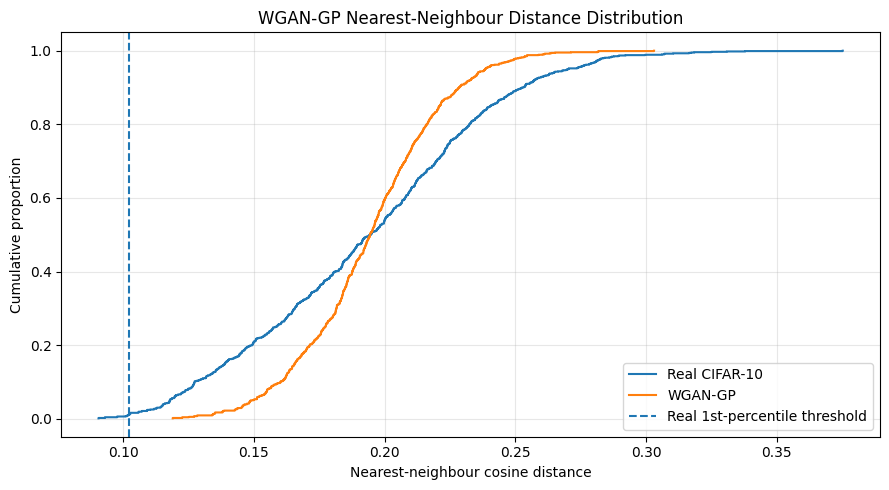

Saved nearest-distance plot: [local project directory]/grids/G03_wgangp_seed42_nearest_distance_ecdf.png


In [129]:
wgan_gp_nearest_distance_plot_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_nearest_distance_ecdf.png"
)

wgan_gp_real_sorted_distances = np.sort(
    wgan_gp_real_nearest_distances
)

wgan_gp_sorted_distances = np.sort(
    wgan_gp_nearest_distances
)

wgan_gp_real_ecdf = np.arange(
    1,
    len(wgan_gp_real_sorted_distances) + 1,
) / len(wgan_gp_real_sorted_distances)

wgan_gp_ecdf = np.arange(
    1,
    len(wgan_gp_sorted_distances) + 1,
) / len(wgan_gp_sorted_distances)

plt.figure(figsize=(9, 5))

plt.step(
    wgan_gp_real_sorted_distances,
    wgan_gp_real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    wgan_gp_sorted_distances,
    wgan_gp_ecdf,
    where="post",
    label="WGAN-GP",
)

plt.axvline(
    wgan_gp_near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "WGAN-GP Nearest-Neighbour Distance Distribution"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    wgan_gp_nearest_distance_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved nearest-distance plot: "
    f"{wgan_gp_nearest_distance_plot_path}"
)

**Interpretation**

The WGAN-GP and real CIFAR-10 nearest-neighbour distributions overlap substantially around their medians, but their overall shapes are not identical.

The WGAN-GP curve begins farther to the right than the real-data curve. This reflects the absence of generated pairs below the real-data near-duplicate threshold of `0.102225`.

The median nearest-neighbour distances are nearly equal:

```text
Real CIFAR-10: 0.194612
WGAN-GP:       0.194483
```

After approximately the median, the WGAN-GP curve rises more steeply and reaches its upper tail earlier than the real distribution.

This suggests that generated nearest-neighbour distances are more concentrated around a middle range. Real CIFAR-10 contains a broader range of both:

unusually similar image pairs
unusually dissimilar image pairs

The generated distribution therefore preserves substantial diversity but does not perfectly reproduce the structure of the real feature distribution.

Together with the `0%` exact-duplicate rate, `0%` feature-space near-duplicate rate and diversity ratio of `0.9401`, the ECDF provides no evidence of severe generated-to-generated repetition.

This analysis does not test whether generated images reproduce particular training images. That question remains reserved for the final generated-to-training memorisation audit in Notebook 4.

#### Most similar generated-image pairs

The ten closest WGAN-GP image pairs are displayed to inspect what the feature-space near-duplicate statistic represents visually.

Pairs may share a broad object type, pose, colour palette or background without being exact duplicates. The images therefore need visual inspection before repeated structure is interpreted as collapse.

In [130]:
wgan_gp_nearest_indices = np.argmin(
    wgan_gp_distance_matrix,
    axis=1,
)

unique_wgan_gp_pairs = {}

for image_index, neighbour_index in enumerate(
    wgan_gp_nearest_indices
):
    pair = tuple(
        sorted(
            (
                int(image_index),
                int(neighbour_index),
            )
        )
    )

    pair_distance = float(
        wgan_gp_distance_matrix[
            pair[0],
            pair[1],
        ]
    )

    if pair not in unique_wgan_gp_pairs:
        unique_wgan_gp_pairs[pair] = (
            pair_distance
        )

wgan_gp_most_similar_pairs = sorted(
    unique_wgan_gp_pairs.items(),
    key=lambda item: item[1],
)[:10]

wgan_gp_similar_pairs_path = (
    GRIDS_DIR
    / f"{WGAN_GP_RUN_ID}_most_similar_pairs.png"
)

fig, axes = plt.subplots(
    5,
    4,
    figsize=(10, 13),
)

for pair_number, (
    pair,
    pair_distance,
) in enumerate(wgan_gp_most_similar_pairs):
    row = pair_number // 2
    column = (pair_number % 2) * 2

    first_index, second_index = pair

    axes[row, column].imshow(
        wgan_gp_diversity_images[
            first_index
        ]
    )

    axes[row, column].set_title(
        f"Pair {pair_number + 1}A",
        fontsize=9,
    )

    axes[row, column].axis("off")

    axes[row, column + 1].imshow(
        wgan_gp_diversity_images[
            second_index
        ]
    )

    axes[row, column + 1].set_title(
        (
            f"Pair {pair_number + 1}B\n"
            f"Distance: {pair_distance:.4f}"
        ),
        fontsize=9,
    )

    axes[row, column + 1].axis("off")

plt.suptitle(
    "WGAN-GP Most Similar Generated Pairs",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    wgan_gp_similar_pairs_path,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved most-similar pairs figure: "
    f"{wgan_gp_similar_pairs_path}"
)

Saved most-similar pairs figure: [local project directory]/grids/G03_wgangp_seed42_most_similar_pairs.png


**Interpretation**

The ten closest WGAN-GP pairs share broad semantic or visual characteristics, but they are not exact or near-identical copies.

The pairs include recurring broad categories such as:

- aircraft or ship-like transport scenes
- cars and other road vehicles
- horse-like or other four-legged animals
- similarly coloured foreground-background layouts

Some individual images appear in more than one closest-pair relationship because one generated sample may be the nearest neighbour of multiple other samples. This does not indicate duplication by itself.

The smallest generated-pair distance was approximately `0.1190`, which remains above the real-data near-duplicate threshold of `0.102225`.

The paired images differ in combinations of:

- colour
- viewpoint
- pose
- object proportions
- foreground placement
- background structure

The figure therefore supports the numerical finding of a `0%` feature-space near-duplicate rate.

However, the closest pairs also show the model's perceptual limitation. Several images share broad transport or animal cues while remaining blurry or structurally ambiguous.

The WGAN-GP result is therefore characterised by:

- strong feature-space diversity
- no exact duplicates
- no detected feature-space near-duplicates
- no evidence of severe mode collapse
- limited clarity and structural precision

#### WGAN-GP result persistence

The selected checkpoint and full architecture-screen evidence are now written to the shared `models_metrics.csv` table. The WGAN-GP row remains unselected until Section 5.4 compares it directly with Dense GAN and DCGAN.

In [131]:
wgan_gp_training_time_minutes = float(
    wgan_gp_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

wgan_gp_diversity_summary = (
    f"Diversity ratio to real: "
    f"{wgan_gp_diversity_ratio:.4f}; "
    f"near-duplicate rate: "
    f"{wgan_gp_near_duplicate_rate:.1f}%; "
    f"exact duplicate rate: "
    f"{wgan_gp_exact_duplicate_rate:.1f}%"
)

wgan_gp_master_df = update_models_metrics(
    {
        "run_id": WGAN_GP_RUN_ID,
        "experiment_family": (
            "architecture_screen"
        ),
        "model": "WGAN-GP",
        "main_change": (
            "Wasserstein objective with "
            "gradient penalty"
        ),
        "seed": WGAN_GP_SEED,
        "epochs_completed": WGAN_GP_EPOCHS,
        "selected_epoch": (
            WGAN_GP_SELECTED_EPOCH
        ),
        "latent_dim": WGAN_GP_LATENT_DIM,
        "batch_size": WGAN_GP_BATCH_SIZE,
        "generator_parameters": (
            wgan_gp_generator.count_params()
        ),
        "adversary_parameters": (
            wgan_gp_critic.count_params()
        ),
        "development_fid": (
            wgan_gp_fid_mean
        ),
        "fid_std": wgan_gp_fid_std,
        "clear_count": wgan_gp_clear_count,
        "marginal_count": (
            wgan_gp_marginal_count
        ),
        "nonsense_count": (
            wgan_gp_nonsense_count
        ),
        "diversity_summary": (
            wgan_gp_diversity_summary
        ),
        "training_time_minutes": (
            wgan_gp_training_time_minutes
        ),
        "selected": False,
        "decision": (
            f"Epoch {WGAN_GP_SELECTED_EPOCH} "
            "selected within the WGAN-GP run. "
            f"Repeated FID {wgan_gp_fid_mean:.2f} "
            f"± {wgan_gp_fid_std:.2f}; "
            f"selected critic gap "
            f"{wgan_gp_selected_score_gap:.3f}; "
            f"recomputed GP "
            f"{wgan_gp_selected_gradient_penalty:.4f}. "
            "Architecture comparison pending."
        ),
    }
)

wgan_gp_master_row = wgan_gp_master_df.loc[
    wgan_gp_master_df["run_id"]
    == WGAN_GP_RUN_ID
]

display(wgan_gp_master_row)

print(
    "WGAN-GP results saved to "
    "models_metrics.csv."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
2,G03_wgangp_seed42,architecture_screen,WGAN-GP,Wasserstein objective with gradient penalty,42,100,50.0,100,64,1085187,662977,54.696368,0.516377,7.0,71.0,22.0,Diversity ratio to real: 0.9401; near-duplicat...,38.648705,False,Epoch 50 selected within the WGAN-GP run. Repe...


WGAN-GP results saved to models_metrics.csv.


#### WGAN-GP findings and limitations

WGAN-GP completed the full 100-epoch architecture-screen process and received the same selected-checkpoint evaluation package as Dense GAN and DCGAN, with additional critic and gradient-penalty diagnostics.

The corrected implementation used consistent generator Batch Normalisation behaviour during both critic and generator phases. Static-adversary validation confirmed that critic updates changed the critic's trainable parameters without changing the generator's trainable parameters. The selected generator and critic also passed fresh-model reload verification.

##### Result summary

| Evidence | WGAN-GP result |
|---|---:|
| Selected checkpoint | Epoch 50 |
| Repeated development FID | `54.6964 ± 0.5164` |
| Clear | 7 out of 100 |
| Marginal | 71 out of 100 |
| Nonsense | 22 out of 100 |
| Diversity ratio to real CIFAR-10 | `0.9401` |
| Generated near-duplicate rate | `0.0%` |
| Exact duplicate rate | `0.0%` |
| Generator parameters | 1,085,187 |
| Critic parameters | 662,977 |
| Recorded training time | 38.65 minutes |
| Independent critic-score gap | `0.7548` |
| Mean interpolated gradient norm | `1.1420` |
| Gradient norms within `[0.8, 1.2]` | `83.7%` |
| Recomputed gradient penalty | `0.0241` |

##### Findings

The corrected WGAN-GP successfully learned diverse CIFAR-10-like image structure.

The selected images demonstrate:

- meaningful foreground-background separation
- varied colour palettes
- object-sized spatial organisation
- transport-related and animal-related visual cues
- variation in pose, viewpoint, background and object placement

Its repeated development FID of approximately `54.7` is a major improvement over the Dense GAN result of approximately `327.3`.

The low-level descriptor comparison also showed close alignment with real CIFAR-10 in brightness, contrast, RGB-channel intensity, saturation and edge strength.

However, semantic recognisability remained limited:

- 7% Clear
- 71% Marginal
- 22% Nonsense

Most images learned plausible low-level appearance and broad object cues without producing sufficiently coherent geometry for confident recognition.

##### Checkpoint behaviour and late deterioration

Epoch 50 was selected because it achieved the lowest milestone development FID:

| Epoch | Development FID |
|---:|---:|
| 50 | **54.1003** |
| 70 | 56.0019 |
| 90 | 104.2449 |
| 100 | 122.7776 |

The result deteriorated substantially after epoch 70.

The fixed-seed grids agree with this pattern. Epochs 40 to 60 contain the strongest visual structures, while epochs 80 to 100 show increased blur, colour smearing and weakened object geometry.

WGAN-GP therefore required early checkpoint selection rather than assuming that the final epoch would be best.

##### WGAN-specific training behaviour

The real-minus-generated critic-score gap remained positive throughout training.

Its phase mean declined from approximately `3.05` during epochs 1–20 to approximately `0.87` during epochs 71–100.

The absolute real and generated critic scores shifted substantially, especially after epoch 70, but generally moved together. Their unrestricted absolute level is not interpreted as a direct quality measure.

The gradient penalty declined during training, but this did not prevent later FID deterioration. A smaller penalty therefore did not imply better generated images.

At the selected checkpoint:

- mean gradient norm was `1.1420`
- median gradient norm was `1.1405`
- 83.7% of norms were between `0.8` and `1.2`
- recomputed gradient penalty was `0.0241`

The gradient penalty constrained the critic meaningfully, but the gradient-norm distribution remained shifted above the target of 1. The result supports approximate rather than perfect enforcement of the critic constraint.

##### Diversity and mode collapse

WGAN-GP showed strong feature-space diversity:

- diversity ratio to real: `0.9401`
- feature-space near-duplicate rate: `0.0%`
- exact duplicate rate: `0.0%`

The nearest-neighbour distribution showed no suspicious lower-tail concentration, and the ten closest generated pairs differed in colour, viewpoint, pose, background or object structure.

There is therefore no evidence of severe mode collapse in the evaluated sample.

The model's main weakness is not repetition. It is limited perceptual clarity and structural coherence.

##### Comparison with DCGAN

WGAN-GP did not improve upon DCGAN under the architecture-screen conditions.

| Evidence | DCGAN | WGAN-GP |
|---|---:|---:|
| Repeated FID | **37.0367 ± 0.3000** | 54.6964 ± 0.5164 |
| Clear | **9** | 7 |
| Marginal | 75 | 71 |
| Nonsense | **16** | 22 |
| Diversity ratio | 0.9324 | **0.9401** |
| Near-duplicate rate | 0.0% | 0.0% |
| Training time | **19.47 min** | 38.65 min |

WGAN-GP achieved a marginally higher diversity ratio, but the difference was small.

DCGAN produced:

- substantially better FID
- slightly more Clear images
- fewer Nonsense images
- sharper and more coherent visual outputs
- stronger late-checkpoint behaviour
- approximately half the training time

WGAN-GP's five critic updates per generator update increased compute cost without producing a corresponding quality advantage.

##### Limitations

- Only 7% of the manual sample met the strict Clear criterion.
- Many outputs remain blurry, malformed or class-ambiguous.
- FID deteriorated severely after epoch 70.
- Absolute critic scores and generator losses became highly variable late in training.
- The gradient-norm distribution was concentrated above the target value of 1.
- A small gradient penalty does not prove perfect Lipschitz enforcement.
- Strong descriptor alignment does not guarantee semantic recognisability.
- FID uses an ImageNet-trained feature extractor on resized CIFAR-10 images and is interpreted comparatively.
- The diversity analysis measures generated-to-generated repetition, not memorisation of training images.
- The formal corrected WGAN-GP result currently represents one training seed.

##### Seed decision

A second corrected WGAN-GP seed is not triggered at this stage.

The quantitative, qualitative, stability and compute evidence all point in the same direction. WGAN-GP is valid and diverse, but weaker than DCGAN for this architecture screen.

A second run would require substantial additional compute and is unlikely to change the current architecture decision sufficiently to justify its cost.

Single-seed uncertainty remains acknowledged as a limitation.

##### Architecture-screen status

WGAN-GP is retained as a valid above-syllabus architecture comparison, but it is not the leading candidate.

Its main strengths are:

- technically valid Wasserstein training
- meaningful gradient-penalty behaviour
- strong feature-space diversity
- no detected severe mode collapse
- substantially better generation than Dense GAN

Its main weaknesses are:

- worse FID than DCGAN
- weaker manual recognisability
- softer and less coherent outputs
- severe late-training deterioration
- approximately double the training time

Final architecture selection remains formally pending until Section 5.4 compares Dense GAN, DCGAN and WGAN-GP together. Based on the evidence currently available, DCGAN is the clear leading architecture for the subsequent improvement experiments.

### 5.4 Architecture Comparison and Provisional Selection

Dense GAN, DCGAN and WGAN-GP have now completed the same primary-seed architecture screen.

The purpose of this comparison is to select one practical architecture foundation for the later controlled experiments.

The decision uses multiple forms of evidence:

- repeated development FID
- fixed-seed and uncurated visual grids
- Clear, Marginal and Nonsense scoring
- descriptor alignment
- feature-space diversity
- near-duplicate and mode-collapse evidence
- training stability
- parameter count
- computational cost

No architecture is selected from one metric alone.

After the provisional winner is identified, its architecture is trained again from fresh weights using the secondary seed. This checks whether the primary-seed result was unusually favourable before the architecture is carried forward.

In [171]:
architecture_screen_run_ids = [
    "G01_dense_seed42",
    "G02_dcgan_seed42",
    "G03_wgangp_seed42",
]

architecture_metrics_df = pd.read_csv(
    MODELS_METRICS_PATH
)

architecture_screen_df = (
    architecture_metrics_df.loc[
        architecture_metrics_df[
            "run_id"
        ].astype(str).isin(
            architecture_screen_run_ids
        )
    ]
    .copy()
)

assert set(
    architecture_screen_df["run_id"].astype(str)
) == set(architecture_screen_run_ids), (
    "One or more architecture-screen rows "
    "are missing from models_metrics.csv."
)

# Extract the persisted diversity statistics.
architecture_screen_df[
    "diversity_ratio"
] = (
    architecture_screen_df[
        "diversity_summary"
    ]
    .astype(str)
    .str.extract(
        r"Diversity ratio to real: ([0-9.]+)"
    )[0]
    .astype(float)
)

architecture_screen_df[
    "near_duplicate_rate"
] = (
    architecture_screen_df[
        "diversity_summary"
    ]
    .astype(str)
    .str.extract(
        r"near-duplicate rate: ([0-9.]+)%"
    )[0]
    .astype(float)
)

architecture_screen_df[
    "exact_duplicate_rate"
] = (
    architecture_screen_df[
        "diversity_summary"
    ]
    .astype(str)
    .str.extract(
        r"exact duplicate rate: ([0-9.]+)%"
    )[0]
    .astype(float)
)

architecture_stability = {
    "G01_dense_seed42": (
        "Stable enough to finish, but poor "
        "quality and severe repetition"
    ),
    "G02_dcgan_seed42": (
        "Strongest checkpoint progression; "
        "quality improved through epoch 100"
    ),
    "G03_wgangp_seed42": (
        "Strongest near epoch 50, followed "
        "by severe late deterioration"
    ),
}

architecture_decisions = {
    "G01_dense_seed42": (
        "Reject"
    ),
    "G02_dcgan_seed42": (
        "Provisional winner"
    ),
    "G03_wgangp_seed42": (
        "Reject"
    ),
}

architecture_screen_df[
    "stability_finding"
] = (
    architecture_screen_df[
        "run_id"
    ].map(architecture_stability)
)

architecture_screen_df[
    "architecture_decision"
] = (
    architecture_screen_df[
        "run_id"
    ].map(architecture_decisions)
)

architecture_screen_df[
    "fid_summary"
] = architecture_screen_df.apply(
    lambda row: (
        f"{float(row['development_fid']):.4f} "
        f"± {float(row['fid_std']):.4f}"
    ),
    axis=1,
)

architecture_screen_df[
    "manual_summary"
] = architecture_screen_df.apply(
    lambda row: (
        f"{int(row['clear_count'])} / "
        f"{int(row['marginal_count'])} / "
        f"{int(row['nonsense_count'])}"
    ),
    axis=1,
)

architecture_model_order = {
    "Dense GAN": 0,
    "DCGAN": 1,
    "WGAN-GP": 2,
}

architecture_screen_df[
    "model_order"
] = architecture_screen_df[
    "model"
].map(architecture_model_order)

architecture_screen_df = (
    architecture_screen_df
    .sort_values("model_order")
    .reset_index(drop=True)
)

architecture_comparison_df = (
    architecture_screen_df[
        [
            "model",
            "selected_epoch",
            "fid_summary",
            "manual_summary",
            "diversity_ratio",
            "near_duplicate_rate",
            "exact_duplicate_rate",
            "training_time_minutes",
            "stability_finding",
            "architecture_decision",
        ]
    ]
    .rename(
        columns={
            "model": "Architecture",
            "selected_epoch": (
                "Selected Epoch"
            ),
            "fid_summary": (
                "Repeated FID"
            ),
            "manual_summary": (
                "Clear / Marginal / Nonsense"
            ),
            "diversity_ratio": (
                "Diversity Ratio"
            ),
            "near_duplicate_rate": (
                "Near-Duplicate Rate (%)"
            ),
            "exact_duplicate_rate": (
                "Exact Duplicate Rate (%)"
            ),
            "training_time_minutes": (
                "Training Time (min)"
            ),
            "stability_finding": (
                "Stability Finding"
            ),
            "architecture_decision": (
                "Decision"
            ),
        }
    )
)

architecture_comparison_df[
    "Selected Epoch"
] = architecture_comparison_df[
    "Selected Epoch"
].astype(int)

display(
    architecture_comparison_df.round(
        {
            "Diversity Ratio": 4,
            "Near-Duplicate Rate (%)": 2,
            "Exact Duplicate Rate (%)": 2,
            "Training Time (min)": 2,
        }
    )
)

architecture_capacity_df = (
    architecture_screen_df[
        [
            "model",
            "generator_parameters",
            "adversary_parameters",
        ]
    ]
    .rename(
        columns={
            "model": "Architecture",
            "generator_parameters": (
                "Generator Parameters"
            ),
            "adversary_parameters": (
                "Adversary Parameters"
            ),
        }
    )
)

display(architecture_capacity_df)

print(
    "Architecture comparison table created."
)

,Architecture,Selected Epoch,Repeated FID,Clear / Marginal / Nonsense,Diversity Ratio,Near-Duplicate Rate (%),Exact Duplicate Rate (%),Training Time (min),Stability Finding,Decision
0,Dense GAN,70,327.2997 ± 0.1871,0 / 20 / 80,0.6648,86.0,0.0,14.85,"Stable enough to finish, but poor quality and ...",Reject
1,DCGAN,100,37.0367 ± 0.3000,9 / 75 / 16,0.9324,0.0,0.0,19.47,Strongest checkpoint progression; quality impr...,Provisional winner
2,WGAN-GP,50,54.6964 ± 0.5164,7 / 71 / 22,0.9401,0.0,0.0,38.65,"Strongest near epoch 50, followed by severe la...",Reject


,Architecture,Generator Parameters,Adversary Parameters
0,Dense GAN,3836928,3803137
1,DCGAN,1085187,664129
2,WGAN-GP,1085187,662977


Architecture comparison table created.


**Interpretation and provisional architecture decision**

The three architecture foundations produced clearly different outcomes.

| Architecture | Main result |
|---|---|
| Dense GAN | Failed to learn reliable semantic object structure and showed severe feature-space repetition |
| DCGAN | Produced the lowest FID, strongest visual progression and best overall quality-compute balance |
| WGAN-GP | Learned meaningful diversity but remained softer, less recognisable, slower and unstable late in training |

Dense GAN is rejected.

Its repeated FID was approximately `327.3`, none of its 100 manually assessed outputs was Clear, and 80 were Nonsense. Its feature-space diversity ratio was only approximately `0.6648`, with 86% of the evaluated images falling below the real-data near-duplicate threshold. The fully connected representation therefore did not provide an adequate spatial inductive bias for CIFAR-10 generation.

WGAN-GP is also rejected as the working architecture.

It substantially improved upon Dense GAN and showed strong feature-space diversity, with a diversity ratio of approximately `0.9401` and no detected near-duplicates. However, its repeated FID of approximately `54.7` remained considerably worse than DCGAN's approximately `37.0`. It also produced fewer Clear images, more Nonsense images, softer object structure and severe deterioration after epoch 70.

WGAN-GP required approximately `38.65` minutes, compared with approximately `19.47` minutes for DCGAN. Its five critic updates per generator update therefore roughly doubled training cost without producing a corresponding quality advantage.

DCGAN is provisionally selected because it provides the strongest combined evidence:

- lowest repeated development FID
- sharper and more coherent generated images
- strongest fixed-seed progression
- fewer Nonsense outputs than WGAN-GP
- no exact or feature-space near-duplicates
- diversity close to the real reference
- lower compute cost than WGAN-GP
- no severe late-checkpoint deterioration

DCGAN's discriminator appeared strong relative to its generator, but this did not prevent it from producing the strongest generated-image evidence in the architecture screen.

The architecture decision remains provisional until the same DCGAN configuration is trained from fresh weights using seed 123.

In [136]:
update_models_metrics(
    {
        "run_id": "G01_dense_seed42",
        "selected": False,
        "decision": (
            "Rejected in the architecture screen. "
            "Very poor FID, no Clear images and "
            "severe feature-space repetition."
        ),
    }
)

update_models_metrics(
    {
        "run_id": "G02_dcgan_seed42",
        "selected": False,
        "decision": (
            "Provisional architecture winner. "
            "Best FID, strongest visual progression "
            "and best quality-compute balance. "
            "Secondary-seed confirmation pending."
        ),
    }
)

architecture_metrics_df = update_models_metrics(
    {
        "run_id": "G03_wgangp_seed42",
        "selected": False,
        "decision": (
            "Rejected as the working architecture. "
            "Valid and diverse, but worse FID, "
            "weaker clarity, late deterioration and "
            "approximately double DCGAN training time."
        ),
    }
)

display(
    architecture_metrics_df.loc[
        architecture_metrics_df[
            "run_id"
        ].astype(str).isin(
            architecture_screen_run_ids
        )
    ]
)

print(
    "Provisional architecture decisions saved."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
0,G01_dense_seed42,architecture_screen,Dense GAN,Fully connected GAN foundation,42,100,70.0,100,64,3836928,3803137,327.299710,0.187123,0.0,20.0,80.0,Diversity ratio to real: 0.6648; near-duplicat...,14.848162,False,Rejected in the architecture screen. Very poor...
1,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100,64,1085187,664129,37.036681,0.299987,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,False,"Provisional architecture winner. Best FID, str..."
2,G03_wgangp_seed42,architecture_screen,WGAN-GP,Wasserstein objective with gradient penalty,42,100,50.0,100,64,1085187,662977,54.696368,0.516377,7.0,71.0,22.0,Diversity ratio to real: 0.9401; near-duplicat...,38.648705,False,Rejected as the working architecture. Valid an...


Provisional architecture decisions saved.


#### Secondary-seed confirmation of DCGAN

The primary-seed architecture comparison provisionally selected DCGAN.

A fresh DCGAN is now trained using seed 123 while keeping every modelling and training setting unchanged.

##### Question

Does the DCGAN architecture retain acceptable quality, diversity and training behaviour when initial weights, latent samples and data-shuffling order change?

##### Controlled factors

| Setting | Value |
|---|---:|
| Architecture | Same DCGAN generator and discriminator |
| Training images | All 50,000 CIFAR-10 training images |
| Epoch budget | 100 |
| Batch size | 64 |
| Latent dimension | 100 |
| Generator learning rate | 0.0002 |
| Discriminator learning rate | 0.0002 |
| Adam beta 1 | 0.5 |
| Adam beta 2 | 0.999 |
| Update ratio | 1 discriminator : 1 generator |
| Augmentation | None |
| Evaluation milestones | 50, 70, 90 and 100 |
| Changed variable | Random seed, from 42 to 123 |

The seed-123 confirmation uses:

- full 100-epoch training
- fixed-seed grids every 10 epochs
- development FID at epochs 50, 70, 90 and 100
- repeated FID for the selected checkpoint
- an uncurated selected-checkpoint grid
- compact diversity and repetition analysis
- training-time comparison

Manual scoring and descriptor analysis are not repeated unless seed 123 behaves materially differently from seed 42.

In [137]:
# DCGAN secondary-seed confirmation settings
DCGAN_CONFIRM_RUN_ID = (
    "G02_dcgan_seed123"
)

DCGAN_CONFIRM_SEED = SECONDARY_SEED
DCGAN_CONFIRM_LATENT_DIM = 100
DCGAN_CONFIRM_BATCH_SIZE = 64
DCGAN_CONFIRM_EPOCHS = 100

DCGAN_CONFIRM_GENERATOR_LR = 2e-4
DCGAN_CONFIRM_DISCRIMINATOR_LR = 2e-4
DCGAN_CONFIRM_BETA_1 = 0.5
DCGAN_CONFIRM_BETA_2 = 0.999

DCGAN_CONFIRM_CHECKPOINT_INTERVAL = 10
DCGAN_CONFIRM_GRID_INTERVAL = 10

DCGAN_CONFIRM_EVALUATION_EPOCHS = (
    50,
    70,
    90,
    100,
)

DCGAN_CONFIRM_MAX_CHECKPOINTS = 3
DCGAN_CONFIRM_FIXED_GRID_SIZE = 25

DCGAN_CONFIRM_CHECKPOINT_DIR = (
    CHECKPOINTS_DIR
    / DCGAN_CONFIRM_RUN_ID
)

DCGAN_CONFIRM_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{DCGAN_CONFIRM_RUN_ID}.csv"
)

DCGAN_CONFIRM_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{DCGAN_CONFIRM_RUN_ID}_"
        "fid_results.csv"
    )
)

DCGAN_CONFIRM_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{DCGAN_CONFIRM_RUN_ID}_"
        "generator.weights.h5"
    )
)

DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{DCGAN_CONFIRM_RUN_ID}_"
        "discriminator.weights.h5"
    )
)

DCGAN_CONFIRM_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    f"Run ID:          "
    f"{DCGAN_CONFIRM_RUN_ID}"
)

print(
    f"Seed:            "
    f"{DCGAN_CONFIRM_SEED}"
)

print(
    f"Checkpoint path: "
    f"{DCGAN_CONFIRM_CHECKPOINT_DIR}"
)

print(
    f"History path:    "
    f"{DCGAN_CONFIRM_HISTORY_PATH}"
)

print(
    f"Epoch budget:    "
    f"{DCGAN_CONFIRM_EPOCHS}"
)

Run ID:          G02_dcgan_seed123
Seed:            123
Checkpoint path: [local project directory]/checkpoints/G02_dcgan_seed123
History path:    [local project directory]/histories/G02_dcgan_seed123.csv
Epoch budget:    100


In [138]:
# Build the confirmation DCGAN generator.
def build_dcgan_confirmation_generator(
    latent_dim,
):

    weight_init = (
        initializers.RandomNormal(
            mean=0.0,
            stddev=0.02,
        )
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.Conv2DTranspose(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                3,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=(
                    weight_init
                ),
            ),
        ],
        name=(
            "DCGAN_Confirmation_Generator"
        ),
    )

    return model

In [139]:
# Build the confirmation DCGAN discriminator.
def build_dcgan_confirmation_discriminator():

    weight_init = (
        initializers.RandomNormal(
            mean=0.0,
            stddev=0.02,
        )
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=(
                    weight_init
                ),
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=(
                    weight_init
                ),
            ),
        ],
        name=(
            "DCGAN_Confirmation_Discriminator"
        ),
    )

    return model

In [140]:
keras.backend.clear_session()

keras.utils.set_random_seed(
    DCGAN_CONFIRM_SEED
)

dcgan_confirm_generator = (
    build_dcgan_confirmation_generator(
        DCGAN_CONFIRM_LATENT_DIM
    )
)

dcgan_confirm_discriminator = (
    build_dcgan_confirmation_discriminator()
)

print(
    "Seed-123 DCGAN generator"
)

dcgan_confirm_generator.summary()

print(
    "\nSeed-123 DCGAN discriminator"
)

dcgan_confirm_discriminator.summary()

print("\nParameter counts")

print(
    "Generator:     "
    f"{dcgan_confirm_generator.count_params():,}"
)

print(
    "Discriminator: "
    f"{dcgan_confirm_discriminator.count_params():,}"
)

assert (
    dcgan_confirm_generator.count_params()
    == 1_085_187
)

assert (
    dcgan_confirm_discriminator.count_params()
    == 664_129
)

dcgan_confirm_test_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=(
            DCGAN_CONFIRM_LATENT_DIM
        ),
        seed=FIXED_LATENT_SEED,
    )
)

dcgan_confirm_test_images = (
    dcgan_confirm_generator(
        dcgan_confirm_test_noise,
        training=False,
    )
)

dcgan_confirm_test_scores = (
    dcgan_confirm_discriminator(
        dcgan_confirm_test_images,
        training=False,
    )
)

assert dcgan_confirm_test_images.shape == (
    8,
    32,
    32,
    3,
)

assert dcgan_confirm_test_scores.shape == (
    8,
    1,
)

assert (
    tf.reduce_min(
        dcgan_confirm_test_images
    ).numpy()
    >= -1.0
)

assert (
    tf.reduce_max(
        dcgan_confirm_test_images
    ).numpy()
    <= 1.0
)

assert (
    tf.reduce_min(
        dcgan_confirm_test_scores
    ).numpy()
    >= 0.0
)

assert (
    tf.reduce_max(
        dcgan_confirm_test_scores
    ).numpy()
    <= 1.0
)

del dcgan_confirm_test_noise
del dcgan_confirm_test_images
del dcgan_confirm_test_scores

print(
    "\nSeed-123 DCGAN architecture "
    "validation passed."
)

Seed-123 DCGAN generator


Model: "DCGAN_Confirmation_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,187 (4.14 MB)

 Trainable params: 1,076,611 (4.11 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,129 (2.53 MB)

 Trainable params: 663,361 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)


Parameter counts
Generator:     1,085,187
Discriminator: 664,129

Seed-123 DCGAN architecture validation passed.


In [146]:
dcgan_confirm_bce = (
    losses.BinaryCrossentropy(
        from_logits=False
    )
)

dcgan_confirm_generator_optimizer = (
    optimizers.Adam(
        learning_rate=(
            DCGAN_CONFIRM_GENERATOR_LR
        ),
        beta_1=(
            DCGAN_CONFIRM_BETA_1
        ),
        beta_2=(
            DCGAN_CONFIRM_BETA_2
        ),
    )
)

dcgan_confirm_discriminator_optimizer = (
    optimizers.Adam(
        learning_rate=(
            DCGAN_CONFIRM_DISCRIMINATOR_LR
        ),
        beta_1=(
            DCGAN_CONFIRM_BETA_1
        ),
        beta_2=(
            DCGAN_CONFIRM_BETA_2
        ),
    )
)

dcgan_confirm_generator_optimizer.build(
    dcgan_confirm_generator
    .trainable_variables
)

dcgan_confirm_discriminator_optimizer.build(
    dcgan_confirm_discriminator
    .trainable_variables
)

dcgan_confirm_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=(
            DCGAN_CONFIRM_BATCH_SIZE
        ),
        seed=DCGAN_CONFIRM_SEED,
    )
)

dcgan_confirm_fixed_noise = (
    make_stateless_noise(
        sample_count=(
            DCGAN_CONFIRM_FIXED_GRID_SIZE
        ),
        latent_dim=(
            DCGAN_CONFIRM_LATENT_DIM
        ),
        seed=FIXED_LATENT_SEED,
    )
)

dcgan_confirm_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        dcgan_confirm_train_dataset
    ).numpy()
)

assert (
    dcgan_confirm_batches_per_epoch
    == 782
)

assert (
    dcgan_confirm_fixed_noise.shape
    == (25, 100)
)

print(
    "Seed-123 DCGAN training "
    "objects created."
)

print(
    f"Batches per epoch: "
    f"{dcgan_confirm_batches_per_epoch}"
)

Seed-123 DCGAN training objects created.
Batches per epoch: 782


In [147]:
dcgan_confirm_completed_epoch = (
    tf.Variable(
        0,
        dtype=tf.int64,
        trainable=False,
        name=(
            "confirmation_completed_epoch"
        ),
    )
)

dcgan_confirm_checkpoint = (
    tf.train.Checkpoint(
        epoch=(
            dcgan_confirm_completed_epoch
        ),
        generator=(
            dcgan_confirm_generator
        ),
        discriminator=(
            dcgan_confirm_discriminator
        ),
        generator_optimizer=(
            dcgan_confirm_generator_optimizer
        ),
        discriminator_optimizer=(
            dcgan_confirm_discriminator_optimizer
        ),
    )
)

dcgan_confirm_checkpoint_manager = (
    tf.train.CheckpointManager(
        checkpoint=(
            dcgan_confirm_checkpoint
        ),
        directory=str(
            DCGAN_CONFIRM_CHECKPOINT_DIR
        ),
        max_to_keep=(
            DCGAN_CONFIRM_MAX_CHECKPOINTS
        ),
    )
)

if (
    dcgan_confirm_checkpoint_manager
    .latest_checkpoint
):
    dcgan_confirm_checkpoint.restore(
        dcgan_confirm_checkpoint_manager
        .latest_checkpoint
    )

    print(
        "Restored checkpoint: "
        f"{dcgan_confirm_checkpoint_manager.latest_checkpoint}"
    )

    print(
        "Restored completed epoch: "
        f"{int(dcgan_confirm_completed_epoch.numpy())}"
    )

else:
    print(
        "No existing seed-123 "
        "checkpoint found."
    )

    print(
        "Confirmation run will begin "
        "from epoch 1."
    )

dcgan_confirm_history = (
    load_and_align_history(
        history_path=(
            DCGAN_CONFIRM_HISTORY_PATH
        ),
        columns=(
            STANDARD_GAN_HISTORY_COLUMNS
        ),
        restored_epoch=int(
            dcgan_confirm_completed_epoch
            .numpy()
        ),
    )
)

print(
    f"History rows available: "
    f"{len(dcgan_confirm_history)}"
)

No existing seed-123 checkpoint found.
Confirmation run will begin from epoch 1.
History rows available: 0


In [148]:
@tf.function
def dcgan_confirmation_train_step(
    real_images,
):

    current_batch_size = tf.shape(
        real_images
    )[0]

    # 1. Discriminator update
    discriminator_noise = (
        tf.random.normal(
            shape=(
                current_batch_size,
                DCGAN_CONFIRM_LATENT_DIM,
            )
        )
    )

    fake_images_for_discriminator = (
        dcgan_confirm_generator(
            discriminator_noise,
            training=False,
        )
    )

    fake_images_for_discriminator = (
        tf.stop_gradient(
            fake_images_for_discriminator
        )
    )

    with tf.GradientTape() as discriminator_tape:
        real_predictions = (
            dcgan_confirm_discriminator(
                real_images,
                training=True,
            )
        )

        fake_predictions = (
            dcgan_confirm_discriminator(
                fake_images_for_discriminator,
                training=True,
            )
        )

        real_loss = dcgan_confirm_bce(
            tf.ones_like(
                real_predictions
            ),
            real_predictions,
        )

        fake_loss = dcgan_confirm_bce(
            tf.zeros_like(
                fake_predictions
            ),
            fake_predictions,
        )

        discriminator_loss = (
            real_loss + fake_loss
        ) / 2.0

    discriminator_gradients = (
        discriminator_tape.gradient(
            discriminator_loss,
            dcgan_confirm_discriminator
            .trainable_variables,
        )
    )

    (
        dcgan_confirm_discriminator_optimizer
        .apply_gradients(
            zip(
                discriminator_gradients,
                dcgan_confirm_discriminator
                .trainable_variables,
            )
        )
    )

    # 2. Generator update
    generator_noise = tf.random.normal(
        shape=(
            current_batch_size,
            DCGAN_CONFIRM_LATENT_DIM,
        )
    )

    with tf.GradientTape() as generator_tape:
        generated_images = (
            dcgan_confirm_generator(
                generator_noise,
                training=True,
            )
        )

        generated_predictions = (
            dcgan_confirm_discriminator(
                generated_images,
                training=True,
            )
        )

        generator_loss = (
            dcgan_confirm_bce(
                tf.ones_like(
                    generated_predictions
                ),
                generated_predictions,
            )
        )

    generator_gradients = (
        generator_tape.gradient(
            generator_loss,
            dcgan_confirm_generator
            .trainable_variables,
        )
    )

    (
        dcgan_confirm_generator_optimizer
        .apply_gradients(
            zip(
                generator_gradients,
                dcgan_confirm_generator
                .trainable_variables,
            )
        )
    )

    return {
        "generator_loss": (
            generator_loss
        ),
        "discriminator_loss": (
            discriminator_loss
        ),
        "real_score": tf.reduce_mean(
            real_predictions
        ),
        "fake_score": tf.reduce_mean(
            fake_predictions
        ),
    }

In [151]:
def save_dcgan_confirmation_state(epoch):

    checkpoint_path = (
        dcgan_confirm_checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        GRIDS_DIR
        / f"{DCGAN_CONFIRM_RUN_ID}_epoch{epoch:03d}.png"
    )

    save_generated_grid(
        generator=dcgan_confirm_generator,
        noise=dcgan_confirm_fixed_noise,
        save_path=grid_path,
        title=f"DCGAN Seed 123, Epoch {epoch}",
    )

    print(
        f"Saved checkpoint: {checkpoint_path}"
    )

    print(
        f"Saved grid:       {grid_path}"
    )

In [152]:
def train_dcgan_confirmation(
    target_epochs,
):

    start_epoch = (
        int(
            dcgan_confirm_completed_epoch
            .numpy()
        )
        + 1
    )

    if start_epoch > target_epochs:
        print(
            "Seed-123 DCGAN is already "
            "trained through epoch "
            f"{int(dcgan_confirm_completed_epoch.numpy())}."
        )

        return load_and_align_history(
            history_path=(
                DCGAN_CONFIRM_HISTORY_PATH
            ),
            columns=(
                STANDARD_GAN_HISTORY_COLUMNS
            ),
            restored_epoch=int(
                dcgan_confirm_completed_epoch
                .numpy()
            ),
        )

    print(
        "Training seed-123 DCGAN from "
        f"epoch {start_epoch} to "
        f"{target_epochs}."
    )

    for epoch in range(
        start_epoch,
        target_epochs + 1,
    ):
        epoch_start_time = time.time()

        generator_loss_mean = (
            keras.metrics.Mean()
        )

        discriminator_loss_mean = (
            keras.metrics.Mean()
        )

        real_score_mean = (
            keras.metrics.Mean()
        )

        fake_score_mean = (
            keras.metrics.Mean()
        )

        for real_images in (
            dcgan_confirm_train_dataset
        ):
            batch_results = (
                dcgan_confirmation_train_step(
                    real_images
                )
            )

            generator_loss_mean.update_state(
                batch_results[
                    "generator_loss"
                ]
            )

            discriminator_loss_mean.update_state(
                batch_results[
                    "discriminator_loss"
                ]
            )

            real_score_mean.update_state(
                batch_results[
                    "real_score"
                ]
            )

            fake_score_mean.update_state(
                batch_results[
                    "fake_score"
                ]
            )

        epoch_time = (
            time.time() - epoch_start_time
        )

        epoch_results = {
            "epoch": epoch,
            "generator_loss": float(
                generator_loss_mean
                .result()
                .numpy()
            ),
            "discriminator_loss": float(
                discriminator_loss_mean
                .result()
                .numpy()
            ),
            "real_score": float(
                real_score_mean
                .result()
                .numpy()
            ),
            "fake_score": float(
                fake_score_mean
                .result()
                .numpy()
            ),
            "epoch_time_seconds": float(
                epoch_time
            ),
        }

        numeric_results = np.array(
            [
                epoch_results[
                    "generator_loss"
                ],
                epoch_results[
                    "discriminator_loss"
                ],
                epoch_results[
                    "real_score"
                ],
                epoch_results[
                    "fake_score"
                ],
                epoch_results[
                    "epoch_time_seconds"
                ],
            ]
        )

        if not np.isfinite(
            numeric_results
        ).all():
            raise FloatingPointError(
                "Non-finite seed-123 "
                "DCGAN value detected at "
                f"epoch {epoch}."
            )

        dcgan_confirm_completed_epoch.assign(
            epoch
        )

        dcgan_confirm_history = (
            save_epoch_history(
                history_path=(
                    DCGAN_CONFIRM_HISTORY_PATH
                ),
                row=epoch_results,
                columns=(
                    STANDARD_GAN_HISTORY_COLUMNS
                ),
            )
        )

        if (
            epoch
            in DCGAN_CONFIRM_EVALUATION_EPOCHS
        ):
            generator_path = (
                WEIGHTS_DIR
                / (
                    f"{DCGAN_CONFIRM_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            discriminator_path = (
                WEIGHTS_DIR
                / (
                    f"{DCGAN_CONFIRM_RUN_ID}_"
                    f"epoch{epoch:03d}_"
                    "discriminator.weights.h5"
                )
            )

            dcgan_confirm_generator.save_weights(
                generator_path
            )

            (
                dcgan_confirm_discriminator
                .save_weights(
                    discriminator_path
                )
            )

            print(
                "Saved milestone generator: "
                f"{generator_path}"
            )

            print(
                "Saved milestone discriminator: "
                f"{discriminator_path}"
            )

        if (
            epoch
            % DCGAN_CONFIRM_CHECKPOINT_INTERVAL
            == 0
            or epoch == target_epochs
        ):
            save_dcgan_confirmation_state(
                epoch=epoch
            )

        print(
            f"Epoch {epoch:03d}/"
            f"{target_epochs} "
            f"| G loss: "
            f"{epoch_results['generator_loss']:.4f} "
            f"| D loss: "
            f"{epoch_results['discriminator_loss']:.4f} "
            f"| Real: "
            f"{epoch_results['real_score']:.4f} "
            f"| Fake: "
            f"{epoch_results['fake_score']:.4f} "
            f"| Time: "
            f"{epoch_results['epoch_time_seconds']:.1f}s"
        )

    total_training_minutes = float(
        dcgan_confirm_history[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    update_models_metrics(
        {
            "run_id": (
                DCGAN_CONFIRM_RUN_ID
            ),
            "experiment_family": (
                "architecture_confirmation"
            ),
            "model": "DCGAN",
            "main_change": (
                "Secondary-seed confirmation "
                "of selected architecture"
            ),
            "seed": (
                DCGAN_CONFIRM_SEED
            ),
            "epochs_completed": int(
                dcgan_confirm_completed_epoch
                .numpy()
            ),
            "latent_dim": (
                DCGAN_CONFIRM_LATENT_DIM
            ),
            "batch_size": (
                DCGAN_CONFIRM_BATCH_SIZE
            ),
            "generator_parameters": (
                dcgan_confirm_generator
                .count_params()
            ),
            "adversary_parameters": (
                dcgan_confirm_discriminator
                .count_params()
            ),
            "training_time_minutes": (
                total_training_minutes
            ),
            "selected": False,
            "decision": (
                "Secondary-seed architecture "
                "confirmation in progress."
            ),
        }
    )

    print(
        "\nSeed-123 DCGAN training complete."
    )

    print(
        f"Completed epoch: "
        f"{int(dcgan_confirm_completed_epoch.numpy())}"
    )

    print(
        "Total recorded training time: "
        f"{total_training_minutes:.2f} minutes"
    )

    return dcgan_confirm_history

#### Training or resuming the seed-123 confirmation

The following cell trains the secondary-seed DCGAN to epoch 100.

If a valid checkpoint exists, the generator, discriminator, both optimiser states, completed epoch and aligned history are restored before training continues.

In [153]:
dcgan_confirm_history = (
    train_dcgan_confirmation(
        target_epochs=(
            DCGAN_CONFIRM_EPOCHS
        )
    )
)

Training seed-123 DCGAN from epoch 1 to 100.
Epoch 001/100 | G loss: 1.1851 | D loss: 0.0910 | Real: 0.9449 | Fake: 0.0576 | Time: 15.3s
Epoch 002/100 | G loss: 1.4977 | D loss: 0.2908 | Real: 0.7905 | Fake: 0.2017 | Time: 11.5s
Epoch 003/100 | G loss: 0.7933 | D loss: 0.1748 | Real: 0.8777 | Fake: 0.1196 | Time: 11.5s
Epoch 004/100 | G loss: 0.9451 | D loss: 0.1107 | Real: 0.9213 | Fake: 0.0774 | Time: 11.5s
Epoch 005/100 | G loss: 1.1036 | D loss: 0.1088 | Real: 0.9230 | Fake: 0.0749 | Time: 11.5s
Epoch 006/100 | G loss: 1.0627 | D loss: 0.0886 | Real: 0.9368 | Fake: 0.0619 | Time: 11.5s
Epoch 007/100 | G loss: 1.3072 | D loss: 0.0945 | Real: 0.9416 | Fake: 0.0576 | Time: 11.5s
Epoch 008/100 | G loss: 1.2693 | D loss: 0.0801 | Real: 0.9429 | Fake: 0.0556 | Time: 11.4s
Epoch 009/100 | G loss: 1.1929 | D loss: 0.0610 | Real: 0.9551 | Fake: 0.0436 | Time: 11.5s
Saved checkpoint: [local project directory]/checkpoints/G02_dcgan_seed123/ckpt-10
Saved grid:       [local project directory]/g

/tmp/ipykernel_1703/4237077900.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


In [154]:
dcgan_confirm_saved_history = (
    pd.read_csv(
        DCGAN_CONFIRM_HISTORY_PATH
    )
)

assert (
    len(dcgan_confirm_saved_history)
    == DCGAN_CONFIRM_EPOCHS
)

assert (
    dcgan_confirm_saved_history[
        "epoch"
    ].tolist()
    == list(
        range(
            1,
            DCGAN_CONFIRM_EPOCHS + 1,
        )
    )
)

assert not dcgan_confirm_saved_history[
    STANDARD_GAN_HISTORY_COLUMNS
].isna().any().any()

assert np.isfinite(
    dcgan_confirm_saved_history[
        [
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ]
    ].to_numpy()
).all()

dcgan_confirm_milestone_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{DCGAN_CONFIRM_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in DCGAN_CONFIRM_EVALUATION_EPOCHS
}

dcgan_confirm_milestone_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{DCGAN_CONFIRM_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch
    in DCGAN_CONFIRM_EVALUATION_EPOCHS
}

dcgan_confirm_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{DCGAN_CONFIRM_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        DCGAN_CONFIRM_GRID_INTERVAL,
        DCGAN_CONFIRM_EPOCHS + 1,
        DCGAN_CONFIRM_GRID_INTERVAL,
    )
}

for path in (
    dcgan_confirm_milestone_generator_paths
    .values()
):
    assert path.exists()

for path in (
    dcgan_confirm_milestone_discriminator_paths
    .values()
):
    assert path.exists()

for path in (
    dcgan_confirm_grid_paths.values()
):
    assert path.exists()

assert (
    int(
        dcgan_confirm_completed_epoch
        .numpy()
    )
    == DCGAN_CONFIRM_EPOCHS
)

dcgan_confirm_training_minutes = float(
    dcgan_confirm_saved_history[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

print(
    "Seed-123 DCGAN artifact "
    "verification passed."
)

print(
    f"History rows: "
    f"{len(dcgan_confirm_saved_history)}"
)

print(
    f"Progression grids: "
    f"{len(dcgan_confirm_grid_paths)}"
)

print(
    "Recorded training time: "
    f"{dcgan_confirm_training_minutes:.2f} "
    "minutes"
)

Seed-123 DCGAN artifact verification passed.
History rows: 100
Progression grids: 10
Recorded training time: 19.38 minutes


#### Seed-123 training diagnostics and fixed-seed progression

The training curves are inspected for numerical failure, prolonged adversarial imbalance or abrupt instability.

The fixed latent vectors are then displayed across all ten saved checkpoints. Because the same latent inputs are reused, changes across epochs reflect training progression rather than changes in sampled noise.

In [155]:
dcgan_confirm_history_df = pd.read_csv(
    DCGAN_CONFIRM_HISTORY_PATH
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

axes[0].plot(
    dcgan_confirm_history_df["epoch"],
    dcgan_confirm_history_df[
        "generator_loss"
    ],
    label="Generator loss",
)

axes[0].plot(
    dcgan_confirm_history_df["epoch"],
    dcgan_confirm_history_df[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

axes[0].set_title(
    "DCGAN Seed 123 Losses"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    dcgan_confirm_history_df["epoch"],
    dcgan_confirm_history_df[
        "real_score"
    ],
    label="Mean real score",
)

axes[1].plot(
    dcgan_confirm_history_df["epoch"],
    dcgan_confirm_history_df[
        "fake_score"
    ],
    label="Mean fake score",
)

axes[1].set_title(
    "DCGAN Seed 123 Discriminator Scores"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean probability")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8),
)

for axis, epoch in zip(
    axes.flat,
    range(10, 101, 10),
):
    grid_path = (
        dcgan_confirm_grid_paths[
            epoch
        ]
    )

    axis.imshow(
        plt.imread(grid_path)
    )

    axis.set_title(
        f"Epoch {epoch}"
    )

    axis.axis("off")

plt.suptitle(
    "DCGAN Seed 123 Fixed-Seed Progression",
    fontsize=15,
)

plt.tight_layout()
plt.show()
plt.close()

print(
    "Seed-123 diagnostics and "
    "progression displayed."
)

Seed-123 diagnostics and progression displayed.


#### Seed-123 milestone development FID

The generator weights saved at epochs 50, 70, 90 and 100 are evaluated using the same:

- 5,000-image sample count
- real CIFAR-10 training reference
- InceptionV3 feature extractor
- preprocessing
- FID implementation
- evaluation latent seed

used for the primary-seed architecture screen.

In [156]:
dcgan_confirm_eval_generator = (
    build_dcgan_confirmation_generator(
        DCGAN_CONFIRM_LATENT_DIM
    )
)

dcgan_confirm_milestone_fid_rows = []

for epoch in (
    DCGAN_CONFIRM_EVALUATION_EPOCHS
):
    milestone_path = (
        dcgan_confirm_milestone_generator_paths[
            epoch
        ]
    )

    (
        dcgan_confirm_eval_generator
        .load_weights(
            milestone_path
        )
    )

    generated_images = (
        generate_images_uint8(
            generator=(
                dcgan_confirm_eval_generator
            ),
            sample_count=(
                ARCH_FID_SAMPLE_COUNT
            ),
            latent_dim=(
                DCGAN_CONFIRM_LATENT_DIM
            ),
            seed=ARCH_FID_SEEDS[0],
        )
    )

    generated_features = (
        extract_inception_features(
            images_uint8=(
                generated_images
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                ARCH_FID_BATCH_SIZE
            ),
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = (
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )
    )

    dcgan_confirm_milestone_fid_rows.append(
        {
            "evaluation": "milestone",
            "epoch": epoch,
            "seed": ARCH_FID_SEEDS[0],
            "sample_count": (
                ARCH_FID_SAMPLE_COUNT
            ),
            "fid": fid_value,
        }
    )

    print(
        f"Epoch {epoch:03d} "
        "development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()

dcgan_confirm_milestone_fid_df = (
    pd.DataFrame(
        dcgan_confirm_milestone_fid_rows
    )
)

dcgan_confirm_milestone_fid_df.to_csv(
    DCGAN_CONFIRM_FID_RESULTS_PATH,
    index=False,
)

dcgan_confirm_milestone_diagnostics_df = (
    dcgan_confirm_history_df.loc[
        dcgan_confirm_history_df[
            "epoch"
        ].isin(
            DCGAN_CONFIRM_EVALUATION_EPOCHS
        ),
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ],
    ]
    .merge(
        dcgan_confirm_milestone_fid_df[
            [
                "epoch",
                "fid",
            ]
        ],
        on="epoch",
        how="left",
    )
    .reset_index(drop=True)
)

display(
    dcgan_confirm_milestone_diagnostics_df
    .round(4)
)

print(
    "Saved seed-123 milestone FID results: "
    f"{DCGAN_CONFIRM_FID_RESULTS_PATH}"
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 46.2692


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 41.1565


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 36.3004


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 39.2296


,epoch,generator_loss,discriminator_loss,real_score,fake_score,epoch_time_seconds,fid
0,50,3.6409,0.1830,0.8982,0.1020,11.4750,46.2692
1,70,4.0589,0.1582,0.9138,0.0859,11.5170,41.1565
2,90,4.6615,0.0992,0.9389,0.0606,11.8179,36.3004
3,100,4.7939,0.1140,0.9370,0.0627,11.8443,39.2296


Saved seed-123 milestone FID results: [local project directory]/histories/G02_dcgan_seed123_fid_results.csv


**Interpretation**

The secondary-seed DCGAN completed all 100 epochs without non-finite values, abrupt collapse or interrupted progression.

The discriminator remained substantially stronger than the generator throughout most of training. By epoch 100:

- the mean real-image score was approximately `0.937`
- the mean generated-image score was approximately `0.063`
- discriminator loss remained low
- generator loss had increased to approximately `4.79`

This indicates persistent discriminator dominance. However, the loss values must not be interpreted as direct image-quality scores.

The fixed-seed progression shows meaningful improvement despite the imbalance.

During epochs 10 to 30, the generator developed:

- broad foreground-background separation
- coarse animal and vehicle forms
- increasingly organised colour regions
- greater variety across latent inputs

From approximately epoch 40 onward, many latent inputs retained stable object layouts while gradually improving their visual structure.

Epochs 70 to 90 appear to provide the strongest region. Several outputs contain recognisable transport-related or animal-related forms, varied backgrounds and distinct compositions.

Epoch 100 remains visually valid and does not show mode collapse. However, it does not provide an obvious qualitative improvement over epoch 90, and some outputs appear slightly softer or less coherent.

The run therefore demonstrates that the DCGAN architecture can learn useful CIFAR-10-like structure under a second initialisation, even though the discriminator remains functionally dominant.

#### Seed-123 checkpoint decision

The milestone results were:

| Epoch | Development FID |
|---:|---:|
| 50 | 46.2692 |
| 70 | 41.1565 |
| 90 | **36.3004** |
| 100 | 39.2296 |

Epoch 90 is selected.

It achieved the lowest development FID and remained within the strongest region of the fixed-seed progression.

Epoch 100 produced broadly similar images, but its FID worsened by approximately `2.93` points. There is no clear qualitative advantage at epoch 100 that justifies overriding the lower epoch-90 FID.

Epochs 50 and 70 are rejected because their FID values are substantially worse and their generated structures are generally less developed.

The selected seed-123 checkpoint is therefore epoch 90.

In [159]:
DCGAN_CONFIRM_SELECTED_EPOCH = 90

dcgan_confirm_selected_generator_milestone_path = (
    dcgan_confirm_milestone_generator_paths[
        DCGAN_CONFIRM_SELECTED_EPOCH
    ]
)

dcgan_confirm_selected_discriminator_milestone_path = (
    dcgan_confirm_milestone_discriminator_paths[
        DCGAN_CONFIRM_SELECTED_EPOCH
    ]
)

dcgan_confirm_selected_generator = (
    build_dcgan_confirmation_generator(
        DCGAN_CONFIRM_LATENT_DIM
    )
)

dcgan_confirm_selected_discriminator = (
    build_dcgan_confirmation_discriminator()
)

dcgan_confirm_selected_generator.load_weights(
    dcgan_confirm_selected_generator_milestone_path
)

dcgan_confirm_selected_discriminator.load_weights(
    dcgan_confirm_selected_discriminator_milestone_path
)

# Save stable selected-weight filenames.
dcgan_confirm_selected_generator.save_weights(
    DCGAN_CONFIRM_SELECTED_GENERATOR_PATH
)

dcgan_confirm_selected_discriminator.save_weights(
    DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH
)

assert (
    DCGAN_CONFIRM_SELECTED_GENERATOR_PATH.exists()
)

assert (
    DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH.exists()
)

print(
    "Selected seed-123 checkpoint: "
    f"epoch {DCGAN_CONFIRM_SELECTED_EPOCH}"
)

print(
    "Selected generator saved:     "
    f"{DCGAN_CONFIRM_SELECTED_GENERATOR_PATH}"
)

print(
    "Selected discriminator saved: "
    f"{DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH}"
)

Selected seed-123 checkpoint: epoch 90
Selected generator saved:     [local project directory]/weights/G02_dcgan_seed123_generator.weights.h5
Selected discriminator saved: [local project directory]/weights/G02_dcgan_seed123_discriminator.weights.h5


In [ ]:
# Recreate and verify the selected epoch-90
# DCGAN seed-123 weights from the canonical
# milestone files.

def maximum_model_weight_difference(
    model_a,
    model_b,
):

    differences = [
        float(
            np.max(
                np.abs(
                    weight_a
                    - weight_b
                )
            )
        )
        for weight_a, weight_b in zip(
            model_a.get_weights(),
            model_b.get_weights(),
        )
    ]

    return max(
        differences,
        default=0.0,
    )


# 1. Load the canonical epoch-90 milestone

dcgan_confirm_canonical_generator = (
    build_dcgan_confirmation_generator(
        DCGAN_CONFIRM_LATENT_DIM
    )
)

dcgan_confirm_canonical_discriminator = (
    build_dcgan_confirmation_discriminator()
)

dcgan_confirm_canonical_generator.load_weights(
    dcgan_confirm_selected_generator_milestone_path
)

dcgan_confirm_canonical_discriminator.load_weights(
    dcgan_confirm_selected_discriminator_milestone_path
)


# 2. Recreate the stable selected-weight files

dcgan_confirm_canonical_generator.save_weights(
    DCGAN_CONFIRM_SELECTED_GENERATOR_PATH
)

dcgan_confirm_canonical_discriminator.save_weights(
    DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH
)

assert (
    DCGAN_CONFIRM_SELECTED_GENERATOR_PATH.exists()
)

assert (
    DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH.exists()
)


# 3. Load those files into fresh models

dcgan_confirm_reloaded_generator = (
    build_dcgan_confirmation_generator(
        DCGAN_CONFIRM_LATENT_DIM
    )
)

dcgan_confirm_reloaded_discriminator = (
    build_dcgan_confirmation_discriminator()
)

dcgan_confirm_reloaded_generator.load_weights(
    DCGAN_CONFIRM_SELECTED_GENERATOR_PATH
)

dcgan_confirm_reloaded_discriminator.load_weights(
    DCGAN_CONFIRM_SELECTED_DISCRIMINATOR_PATH
)


# 4. Compare all trainable and non-trainable weights

dcgan_confirm_generator_weight_difference = (
    maximum_model_weight_difference(
        dcgan_confirm_canonical_generator,
        dcgan_confirm_reloaded_generator,
    )
)

dcgan_confirm_discriminator_weight_difference = (
    maximum_model_weight_difference(
        dcgan_confirm_canonical_discriminator,
        dcgan_confirm_reloaded_discriminator,
    )
)


# 5. Compare inference outputs

dcgan_confirm_reload_noise = (
    make_stateless_noise(
        sample_count=16,
        latent_dim=(
            DCGAN_CONFIRM_LATENT_DIM
        ),
        seed=9123,
    )
)

dcgan_confirm_canonical_images = (
    dcgan_confirm_canonical_generator(
        dcgan_confirm_reload_noise,
        training=False,
    )
)

dcgan_confirm_reloaded_images = (
    dcgan_confirm_reloaded_generator(
        dcgan_confirm_reload_noise,
        training=False,
    )
)

dcgan_confirm_generator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            dcgan_confirm_canonical_images
            - dcgan_confirm_reloaded_images
        )
    ).numpy()
)

# Use the same image batch for both discriminators
# so only discriminator restoration is tested.
dcgan_confirm_canonical_scores = (
    dcgan_confirm_canonical_discriminator(
        dcgan_confirm_canonical_images,
        training=False,
    )
)

dcgan_confirm_reloaded_scores = (
    dcgan_confirm_reloaded_discriminator(
        dcgan_confirm_canonical_images,
        training=False,
    )
)

dcgan_confirm_discriminator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            dcgan_confirm_canonical_scores
            - dcgan_confirm_reloaded_scores
        )
    ).numpy()
)


# Assertions

assert (
    dcgan_confirm_generator_weight_difference
    < 1e-7
)

assert (
    dcgan_confirm_discriminator_weight_difference
    < 1e-7
)

# A slightly looser tolerance is appropriate for
# GPU convolution outputs.
assert (
    dcgan_confirm_generator_output_difference
    < 1e-5
)

assert (
    dcgan_confirm_discriminator_output_difference
    < 1e-5
)


# Keep the verified canonical models as the active
# selected seed-123 models in this runtime.
dcgan_confirm_selected_generator = (
    dcgan_confirm_canonical_generator
)

dcgan_confirm_selected_discriminator = (
    dcgan_confirm_canonical_discriminator
)


print(
    "Seed-123 selected-weight reload "
    "verification passed."
)

print(
    "Maximum generator weight difference:     "
    f"{dcgan_confirm_generator_weight_difference:.10f}"
)

print(
    "Maximum discriminator weight difference: "
    f"{dcgan_confirm_discriminator_weight_difference:.10f}"
)

print(
    "Maximum generator output difference:     "
    f"{dcgan_confirm_generator_output_difference:.10f}"
)

print(
    "Maximum discriminator output difference: "
    f"{dcgan_confirm_discriminator_output_difference:.10f}"
)

Seed-123 selected-weight reload verification passed.
Maximum generator weight difference:     0.0000000000
Maximum discriminator weight difference: 0.0000000000
Maximum generator output difference:     0.0000002384
Maximum discriminator output difference: 0.0000000000


#### Repeated FID for the selected seed-123 checkpoint

The selected epoch-90 generator is evaluated using three independently generated 5,000-image samples.

The same real reference, feature extractor, preprocessing and FID implementation used throughout the architecture screen are retained.

In [160]:
dcgan_confirm_repeated_fid_rows = []

dcgan_confirm_selected_reference_images = None
dcgan_confirm_selected_reference_features = None

for fid_seed in ARCH_FID_SEEDS:

    generated_images = generate_images_uint8(
        generator=(
            dcgan_confirm_selected_generator
        ),
        sample_count=(
            ARCH_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            DCGAN_CONFIRM_LATENT_DIM
        ),
        seed=fid_seed,
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                ARCH_FID_BATCH_SIZE
            ),
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = (
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )
    )

    dcgan_confirm_repeated_fid_rows.append(
        {
            "evaluation": (
                "selected_checkpoint_repeat"
            ),
            "epoch": (
                DCGAN_CONFIRM_SELECTED_EPOCH
            ),
            "seed": fid_seed,
            "sample_count": (
                ARCH_FID_SAMPLE_COUNT
            ),
            "fid": fid_value,
        }
    )

    print(
        f"Seed {fid_seed} FID: "
        f"{fid_value:.4f}"
    )

    # Retain one sample for the compact
    # diversity and repetition checks.
    if fid_seed == ARCH_FID_SEEDS[0]:
        dcgan_confirm_selected_reference_images = (
            generated_images
        )

        dcgan_confirm_selected_reference_features = (
            generated_features
        )

    else:
        del generated_images
        del generated_features

    del generated_mean
    del generated_covariance

    gc.collect()

dcgan_confirm_repeated_fid_df = (
    pd.DataFrame(
        dcgan_confirm_repeated_fid_rows
    )
)

dcgan_confirm_fid_mean = float(
    dcgan_confirm_repeated_fid_df[
        "fid"
    ].mean()
)

dcgan_confirm_fid_std = float(
    dcgan_confirm_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)

dcgan_confirm_existing_fid_df = (
    pd.read_csv(
        DCGAN_CONFIRM_FID_RESULTS_PATH
    )
)

dcgan_confirm_milestone_only_df = (
    dcgan_confirm_existing_fid_df.loc[
        dcgan_confirm_existing_fid_df[
            "evaluation"
        ].astype(str) == "milestone"
    ]
    .copy()
)

dcgan_confirm_all_fid_results_df = (
    pd.concat(
        [
            dcgan_confirm_milestone_only_df,
            dcgan_confirm_repeated_fid_df,
        ],
        ignore_index=True,
    )
)

dcgan_confirm_all_fid_results_df.to_csv(
    DCGAN_CONFIRM_FID_RESULTS_PATH,
    index=False,
)

display(
    dcgan_confirm_repeated_fid_df.round(4)
)

print(
    f"Repeated FID mean: "
    f"{dcgan_confirm_fid_mean:.4f}"
)

print(
    f"Repeated FID SD:   "
    f"{dcgan_confirm_fid_std:.4f}"
)

assert (
    dcgan_confirm_selected_reference_images.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )
)

assert (
    dcgan_confirm_selected_reference_features.shape
    == (
        ARCH_FID_SAMPLE_COUNT,
        ARCH_FID_FEATURE_DIM,
    )
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1001 FID: 36.3004


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 36.6598


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 36.5539


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,90,1001,5000,36.3004
1,selected_checkpoint_repeat,90,1002,5000,36.6598
2,selected_checkpoint_repeat,90,1003,5000,36.5539


Repeated FID mean: 36.5047
Repeated FID SD:   0.1847


**Interpretation**

The selected seed-123 checkpoint produced highly consistent development FID results across three independently generated 5,000-image samples:

| Sampling seed | FID |
|---:|---:|
| 1001 | 36.3004 |
| 1002 | 36.6598 |
| 1003 | 36.5539 |
| **Mean** | **36.5047** |
| **Standard deviation** | **0.1847** |

The low standard deviation indicates that the result is not dependent on one unusually favourable latent sample.

The seed-123 mean FID is slightly better than the seed-42 mean of approximately `37.0367`. However, the difference of approximately `0.5320` is small relative to the overall scale of the metric.

Both independently trained DCGANs therefore reached the same general performance region.

This supports the conclusion that the architecture's strong architecture-screen result was not caused by one unusually favourable initialisation.

#### Uncurated seed-123 checkpoint grid

A separate latent seed is used to generate an uncurated 25-image grid from the selected epoch-90 checkpoint.

This checks whether the fixed progression grid was unusually favourable.

In [161]:
DCGAN_CONFIRM_UNCURATED_SEED = 8123
DCGAN_CONFIRM_UNCURATED_COUNT = 25

dcgan_confirm_uncurated_images = (
    generate_images_uint8(
        generator=(
            dcgan_confirm_selected_generator
        ),
        sample_count=(
            DCGAN_CONFIRM_UNCURATED_COUNT
        ),
        latent_dim=(
            DCGAN_CONFIRM_LATENT_DIM
        ),
        seed=(
            DCGAN_CONFIRM_UNCURATED_SEED
        ),
    )
)

dcgan_confirm_uncurated_grid_path = (
    GRIDS_DIR
    / (
        f"{DCGAN_CONFIRM_RUN_ID}_"
        f"selected_epoch"
        f"{DCGAN_CONFIRM_SELECTED_EPOCH:03d}_"
        "uncurated.png"
    )
)

fig, axes = plt.subplots(
    5,
    5,
    figsize=(10, 10),
)

for index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        dcgan_confirm_uncurated_images[
            index
        ]
    )

    axis.axis("off")

plt.suptitle(
    "DCGAN Seed 123 Uncurated Grid, "
    f"Epoch {DCGAN_CONFIRM_SELECTED_EPOCH}",
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    dcgan_confirm_uncurated_grid_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved uncurated grid: "
    f"{dcgan_confirm_uncurated_grid_path}"
)

Saved uncurated grid: [local project directory]/grids/G02_dcgan_seed123_selected_epoch090_uncurated.png


**Interpretation**

The uncurated seed-123 grid confirms that the selected epoch-90 checkpoint generates meaningful CIFAR-10-like structure beyond the fixed latent progression.

The grid includes varied forms resembling:

- aircraft and ships
- cars and other road vehicles
- horses and other four-legged animals
- birds or small animals
- objects against natural, urban, sky and water backgrounds

Several images have recognisable foreground silhouettes and plausible colour organisation.

Some outputs remain blurry, malformed or class-ambiguous. This is expected for the compact architecture-screen model and the low `32 × 32` CIFAR-10 resolution.

The 25 samples remain visibly different in object type, colour, pose, viewpoint and background. There is no obvious evidence of mode collapse or repeated templates.

The uncurated output is broadly consistent with the seed-42 DCGAN result and supports the robustness of the architecture.

#### Compact seed-123 diversity and repetition check

A matched sample of 1,000 generated images and 1,000 real CIFAR-10 training images is compared in normalised Inception feature space.

The analysis reports:

- mean and median pairwise cosine distance
- median nearest-neighbour distance
- diversity relative to real CIFAR-10
- generated near-duplicate rate
- exact generated duplicate rate

This is a generated-to-generated repetition check. It is not the final generated-to-training memorisation audit.

In [ ]:
DCGAN_CONFIRM_DIVERSITY_SAMPLE_COUNT = 1_000
DCGAN_CONFIRM_DIVERSITY_SEED = 2026

dcgan_confirm_diversity_rng = (
    np.random.default_rng(
        DCGAN_CONFIRM_DIVERSITY_SEED
    )
)

generated_diversity_indices = (
    dcgan_confirm_diversity_rng.choice(
        len(
            dcgan_confirm_selected_reference_features
        ),
        size=(
            DCGAN_CONFIRM_DIVERSITY_SAMPLE_COUNT
        ),
        replace=False,
    )
)

real_diversity_indices = (
    dcgan_confirm_diversity_rng.choice(
        len(x_train_gan),
        size=(
            DCGAN_CONFIRM_DIVERSITY_SAMPLE_COUNT
        ),
        replace=False,
    )
)

dcgan_confirm_generated_diversity_features = (
    dcgan_confirm_selected_reference_features[
        generated_diversity_indices
    ]
)

dcgan_confirm_real_diversity_images = np.clip(
    (
        x_train_gan[
            real_diversity_indices
        ]
        + 1.0
    )
    * 127.5,
    0,
    255,
).astype(np.uint8)

dcgan_confirm_real_diversity_features = (
    extract_inception_features(
        images_uint8=(
            dcgan_confirm_real_diversity_images
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=(
            ARCH_FID_BATCH_SIZE
        ),
    )
)


def compact_cosine_diversity_summary(
    features,
):

    features = np.asarray(
        features,
        dtype=np.float32,
    )

    feature_norms = np.linalg.norm(
        features,
        axis=1,
        keepdims=True,
    )

    feature_norms = np.maximum(
        feature_norms,
        1e-12,
    )

    normalised_features = (
        features / feature_norms
    )

    similarity_matrix = (
        normalised_features
        @ normalised_features.T
    )

    distance_matrix = np.clip(
        1.0 - similarity_matrix,
        0.0,
        2.0,
    )

    upper_triangle_indices = (
        np.triu_indices(
            len(features),
            k=1,
        )
    )

    pairwise_distances = (
        distance_matrix[
            upper_triangle_indices
        ]
    )

    np.fill_diagonal(
        distance_matrix,
        np.inf,
    )

    nearest_distances = (
        distance_matrix.min(axis=1)
    )

    return {
        "mean_pairwise_distance": float(
            pairwise_distances.mean()
        ),
        "median_pairwise_distance": float(
            np.median(
                pairwise_distances
            )
        ),
        "median_nearest_distance": float(
            np.median(
                nearest_distances
            )
        ),
        "minimum_nearest_distance": float(
            nearest_distances.min()
        ),
        "nearest_distances": (
            nearest_distances
        ),
    }


dcgan_confirm_real_diversity_summary = (
    compact_cosine_diversity_summary(
        dcgan_confirm_real_diversity_features
    )
)

dcgan_confirm_generated_diversity_summary = (
    compact_cosine_diversity_summary(
        dcgan_confirm_generated_diversity_features
    )
)

dcgan_confirm_near_duplicate_threshold = float(
    np.percentile(
        dcgan_confirm_real_diversity_summary[
            "nearest_distances"
        ],
        1,
    )
)

dcgan_confirm_near_duplicate_rate = float(
    np.mean(
        dcgan_confirm_generated_diversity_summary[
            "nearest_distances"
        ]
        < dcgan_confirm_near_duplicate_threshold
    )
    * 100.0
)

dcgan_confirm_diversity_ratio = float(
    dcgan_confirm_generated_diversity_summary[
        "mean_pairwise_distance"
    ]
    / dcgan_confirm_real_diversity_summary[
        "mean_pairwise_distance"
    ]
)

dcgan_confirm_flattened_images = (
    dcgan_confirm_selected_reference_images
    .reshape(
        len(
            dcgan_confirm_selected_reference_images
        ),
        -1,
    )
)

dcgan_confirm_unique_image_count = int(
    np.unique(
        dcgan_confirm_flattened_images,
        axis=0,
    ).shape[0]
)

dcgan_confirm_exact_duplicate_rate = float(
    (
        1.0
        - (
            dcgan_confirm_unique_image_count
            / len(
                dcgan_confirm_selected_reference_images
            )
        )
    )
    * 100.0
)

dcgan_confirm_diversity_df = (
    pd.DataFrame(
        [
            {
                "Source": "Real CIFAR-10",
                "Mean Pairwise Distance": (
                    dcgan_confirm_real_diversity_summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Median Pairwise Distance": (
                    dcgan_confirm_real_diversity_summary[
                        "median_pairwise_distance"
                    ]
                ),
                "Median Nearest Distance": (
                    dcgan_confirm_real_diversity_summary[
                        "median_nearest_distance"
                    ]
                ),
                "Minimum Nearest Distance": (
                    dcgan_confirm_real_diversity_summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-Duplicate Rate (%)": 1.0,
            },
            {
                "Source": "DCGAN Seed 123",
                "Mean Pairwise Distance": (
                    dcgan_confirm_generated_diversity_summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Median Pairwise Distance": (
                    dcgan_confirm_generated_diversity_summary[
                        "median_pairwise_distance"
                    ]
                ),
                "Median Nearest Distance": (
                    dcgan_confirm_generated_diversity_summary[
                        "median_nearest_distance"
                    ]
                ),
                "Minimum Nearest Distance": (
                    dcgan_confirm_generated_diversity_summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-Duplicate Rate (%)": (
                    dcgan_confirm_near_duplicate_rate
                ),
            },
        ]
    )
)

display(
    dcgan_confirm_diversity_df.round(6)
)

print(
    "Real-data near-duplicate threshold: "
    f"{dcgan_confirm_near_duplicate_threshold:.6f}"
)

print(
    "Generated-to-real diversity ratio: "
    f"{dcgan_confirm_diversity_ratio:.4f}"
)

print(
    "Generated near-duplicate rate: "
    f"{dcgan_confirm_near_duplicate_rate:.2f}%"
)

print(
    "Generated exact duplicate rate: "
    f"{dcgan_confirm_exact_duplicate_rate:.2f}%"
)

**Interpretation**

The seed-123 DCGAN retained strong feature-space diversity.

| Measure | Real CIFAR-10 | DCGAN seed 123 |
|---|---:|---:|
| Mean pairwise distance | 0.376803 | 0.359019 |
| Median pairwise distance | 0.377786 | 0.357505 |
| Median nearest-neighbour distance | 0.199640 | 0.200070 |
| Minimum nearest-neighbour distance | 0.044375 | 0.132199 |
| Near-duplicate rate | 1.0% reference threshold | 0.0% |

The generated-to-real diversity ratio was `0.9528`. The overall generated feature spread was therefore approximately 95.3% of the real CIFAR-10 reference spread.

The generated and real median nearest-neighbour distances were nearly identical:

```text
Real CIFAR-10: 0.199640
DCGAN seed 123: 0.200070
```

No generated image fell below the real-data first-percentile near-duplicate threshold of `0.098152`.

There were also no exact pixel duplicates among the retained 5,000 generated images.

The seed-123 run therefore shows no evidence of severe mode collapse, exact repetition or excessive feature-space similarity.

Its diversity ratio is slightly higher than the seed-42 result of approximately `0.9324`, further supporting that the DCGAN architecture preserves useful variety across independent training runs.

In [163]:
dcgan_confirm_diversity_summary_text = (
    "Diversity ratio to real: "
    f"{dcgan_confirm_diversity_ratio:.4f}; "
    "near-duplicate rate: "
    f"{dcgan_confirm_near_duplicate_rate:.2f}%; "
    "exact duplicate rate: "
    f"{dcgan_confirm_exact_duplicate_rate:.2f}%"
)

architecture_metrics_df = (
    update_models_metrics(
        {
            "run_id": (
                DCGAN_CONFIRM_RUN_ID
            ),
            "experiment_family": (
                "architecture_confirmation"
            ),
            "model": "DCGAN",
            "main_change": (
                "Secondary-seed confirmation "
                "of selected architecture"
            ),
            "seed": (
                DCGAN_CONFIRM_SEED
            ),
            "epochs_completed": (
                DCGAN_CONFIRM_EPOCHS
            ),
            "selected_epoch": (
                DCGAN_CONFIRM_SELECTED_EPOCH
            ),
            "latent_dim": (
                DCGAN_CONFIRM_LATENT_DIM
            ),
            "batch_size": (
                DCGAN_CONFIRM_BATCH_SIZE
            ),
            "generator_parameters": (
                dcgan_confirm_selected_generator
                .count_params()
            ),
            "adversary_parameters": (
                dcgan_confirm_selected_discriminator
                .count_params()
            ),
            "development_fid": (
                dcgan_confirm_fid_mean
            ),
            "fid_std": (
                dcgan_confirm_fid_std
            ),
            "diversity_summary": (
                dcgan_confirm_diversity_summary_text
            ),
            "training_time_minutes": (
                dcgan_confirm_training_minutes
            ),
            "selected": False,
            "decision": (
                "Secondary seed confirms the "
                "DCGAN architecture. Epoch 90 "
                "selected using FID, visual "
                "progression and stability."
            ),
        }
    )
)

display(
    architecture_metrics_df.loc[
        architecture_metrics_df[
            "run_id"
        ].astype(str).isin(
            [
                "G02_dcgan_seed42",
                "G02_dcgan_seed123",
            ]
        )
    ]
)

print(
    "Seed-123 confirmation metrics saved."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
1,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100,64,1085187,664129,37.036681,0.299987,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,False,"Provisional architecture winner. Best FID, str..."
3,G02_dcgan_seed123,architecture_confirmation,DCGAN,Secondary-seed confirmation of selected archit...,123,100,90.0,100,64,1085187,664129,36.504696,0.184696,NaN,NaN,NaN,Diversity ratio to real: 0.9528; near-duplicat...,19.380622,False,Secondary seed confirms the DCGAN architecture...


Seed-123 confirmation metrics saved.


#### DCGAN seed robustness comparison

The primary and secondary DCGAN runs are now compared using:

- selected checkpoint
- repeated FID
- diversity ratio
- near-duplicate rate
- exact duplicate rate
- training time

The purpose is not to require identical results. It is to determine whether the selected architecture remains competitive under a second random initialisation.

In [167]:
dcgan_seed_metrics_df = pd.read_csv(
    MODELS_METRICS_PATH
)

dcgan_seed_comparison_rows = []

for run_id, seed_label in [
    (
        "G02_dcgan_seed42",
        "Seed 42",
    ),
    (
        "G02_dcgan_seed123",
        "Seed 123",
    ),
]:
    run_row = (
        dcgan_seed_metrics_df.loc[
            dcgan_seed_metrics_df[
                "run_id"
            ].astype(str) == run_id
        ]
        .iloc[0]
    )

    diversity_text = str(
        run_row["diversity_summary"]
    )

    diversity_ratio = float(
        re.search(
            r"Diversity ratio to real: "
            r"([0-9.]+)",
            diversity_text,
        ).group(1)
    )

    near_duplicate_rate = float(
        re.search(
            r"near-duplicate rate: "
            r"([0-9.]+)%",
            diversity_text,
        ).group(1)
    )

    exact_duplicate_rate = float(
        re.search(
            r"exact duplicate rate: "
            r"([0-9.]+)%",
            diversity_text,
        ).group(1)
    )

    dcgan_seed_comparison_rows.append(
        {
            "Run": run_id,
            "Seed": seed_label,
            "Selected Epoch": int(
                run_row[
                    "selected_epoch"
                ]
            ),
            "Repeated FID Mean": float(
                run_row[
                    "development_fid"
                ]
            ),
            "Repeated FID SD": float(
                run_row[
                    "fid_std"
                ]
            ),
            "Diversity Ratio": (
                diversity_ratio
            ),
            "Near-Duplicate Rate (%)": (
                near_duplicate_rate
            ),
            "Exact Duplicate Rate (%)": (
                exact_duplicate_rate
            ),
            "Training Time (min)": float(
                run_row[
                    "training_time_minutes"
                ]
            ),
        }
    )

dcgan_seed_comparison_df = pd.DataFrame(
    dcgan_seed_comparison_rows
)

display(
    dcgan_seed_comparison_df.round(4)
)

dcgan_cross_seed_fid_mean = float(
    dcgan_seed_comparison_df[
        "Repeated FID Mean"
    ].mean()
)

dcgan_cross_seed_fid_range = float(
    dcgan_seed_comparison_df[
        "Repeated FID Mean"
    ].max()
    - dcgan_seed_comparison_df[
        "Repeated FID Mean"
    ].min()
)

print(
    "Mean repeated FID across training seeds: "
    f"{dcgan_cross_seed_fid_mean:.4f}"
)

print(
    "Difference between seed-level FID means: "
    f"{dcgan_cross_seed_fid_range:.4f}"
)

,Run,Seed,Selected Epoch,Repeated FID Mean,Repeated FID SD,Diversity Ratio,Near-Duplicate Rate (%),Exact Duplicate Rate (%),Training Time (min)
0,G02_dcgan_seed42,Seed 42,100,37.0367,0.3000,0.9324,0.0,0.0,19.4674
1,G02_dcgan_seed123,Seed 123,90,36.5047,0.1847,0.9528,0.0,0.0,19.3806


Mean repeated FID across training seeds: 36.7707
Difference between seed-level FID means: 0.5320


**Interpretation**

The secondary-seed run confirms that the DCGAN architecture is robust to a change in random initialisation.

| Evidence | Seed 42 | Seed 123 |
|---|---:|---:|
| Selected epoch | 100 | 90 |
| Repeated FID | `37.0367 ± 0.3000` | `36.5047 ± 0.1847` |
| Diversity ratio | 0.9324 | 0.9528 |
| Near-duplicate rate | 0.0% | 0.0% |
| Exact duplicate rate | 0.0% | 0.0% |
| Training time | 19.47 min | 19.38 min |

The mean repeated FID across the two independent training seeds was approximately `36.7707`.

The difference between their seed-level means was only approximately `0.5320`. This is small compared with:

- DCGAN's advantage over WGAN-GP
- DCGAN's very large advantage over Dense GAN
- the overall scale of the FID metric

The selected checkpoints differed slightly, with epoch 100 selected for seed 42 and epoch 90 selected for seed 123. This is normal for adversarial training because the strongest checkpoint need not occur at exactly the same epoch across independent runs.

Both runs nevertheless showed:

- progressive development of CIFAR-10-like structure
- repeated FID in the same narrow performance region
- no exact duplicates
- no detected feature-space near-duplicates
- diversity close to the real CIFAR-10 reference
- nearly identical training cost
- no catastrophic mode collapse

The seed-123 run therefore confirms that the primary DCGAN result was not an isolated or unusually favourable outcome.

### 5.5 Final Architecture-Screen Decision

DCGAN is selected as the architecture foundation for the controlled improvement experiments.

#### Final comparison

| Evidence | Dense GAN | DCGAN | WGAN-GP |
|---|---:|---:|---:|
| Representative repeated FID | ≈327.3 | **≈36.8 across two seeds** | ≈54.7 |
| Clear images | 0 | **9** | 7 |
| Nonsense images | 80 | **16** | 22 |
| Diversity | Severely compressed | Strong | Strong |
| Near-duplicate behaviour | Severe repetition | No detected issue | No detected issue |
| Training stability | Completed but poor quality | Strongest overall progression | Deteriorated severely after epoch 70 |
| Training time | 14.85 min | **≈19.4 min** | 38.65 min |
| Architecture decision | Reject | **Select** | Reject |

Dense GAN is rejected because removing spatial convolutional structure resulted in extremely poor FID, no Clear images and severe feature-space repetition.

WGAN-GP is retained as a valid above-syllabus comparison, but rejected as the working architecture because it produced worse FID, fewer Clear images, more Nonsense images, softer object structure, severe late-training deterioration and approximately twice the DCGAN training cost.

DCGAN achieved the strongest balance of:

- distribution similarity
- perceptual quality
- recognisability
- diversity
- resistance to repetition
- training stability
- computational efficiency
- reproducibility across seeds

Seed 123 slightly outperformed seed 42 quantitatively, but seed 42 remains the canonical architecture-screen reference because it received the complete manual, descriptor and diversity evaluation package. Seed 123 serves as independent robustness confirmation rather than replacing the primary experiment.

The architecture is now locked for the next stage. Later experiments will change one controlled factor at a time while retaining the same convolutional generator and discriminator foundation.

In [168]:
update_models_metrics(
    {
        "run_id": "G01_dense_seed42",
        "selected": False,
        "decision": (
            "Rejected during architecture selection. "
            "Extremely poor FID, no Clear images and "
            "severe feature-space repetition."
        ),
    }
)

update_models_metrics(
    {
        "run_id": "G03_wgangp_seed42",
        "selected": False,
        "decision": (
            "Rejected as the working architecture. "
            "Valid and diverse, but worse FID, weaker "
            "recognisability, late deterioration and "
            "approximately double DCGAN training time."
        ),
    }
)

update_models_metrics(
    {
        "run_id": "G02_dcgan_seed123",
        "selected": False,
        "decision": (
            "Secondary-seed confirmation. The result "
            "confirmed DCGAN robustness with repeated "
            "FID 36.5047 ± 0.1847 and strong diversity."
        ),
    }
)

final_architecture_metrics_df = (
    update_models_metrics(
        {
            "run_id": "G02_dcgan_seed42",
            "selected": True,
            "decision": (
                "Selected architecture-screen foundation. "
                "Best overall quality, FID, stability, "
                "diversity, compute efficiency and "
                "cross-seed reproducibility."
            ),
        }
    )
)

display(
    final_architecture_metrics_df.loc[
        final_architecture_metrics_df[
            "run_id"
        ].astype(str).isin(
            [
                "G01_dense_seed42",
                "G02_dcgan_seed42",
                "G02_dcgan_seed123",
                "G03_wgangp_seed42",
            ]
        )
    ]
)

selected_architecture_rows = (
    final_architecture_metrics_df.loc[
        final_architecture_metrics_df[
            "selected"
        ] == True
    ]
)

assert (
    selected_architecture_rows[
        "run_id"
    ].astype(str).tolist()
    == ["G02_dcgan_seed42"]
)

print(
    "Architecture screen closed."
)

print(
    "Selected architecture: DCGAN"
)

print(
    "Canonical reference run: "
    "G02_dcgan_seed42"
)

print(
    "Robustness confirmation run: "
    "G02_dcgan_seed123"
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
0,G01_dense_seed42,architecture_screen,Dense GAN,Fully connected GAN foundation,42,100,70.0,100,64,3836928,3803137,327.299710,0.187123,0.0,20.0,80.0,Diversity ratio to real: 0.6648; near-duplicat...,14.848162,False,Rejected during architecture selection. Extrem...
1,G03_wgangp_seed42,architecture_screen,WGAN-GP,Wasserstein objective with gradient penalty,42,100,50.0,100,64,1085187,662977,54.696368,0.516377,7.0,71.0,22.0,Diversity ratio to real: 0.9401; near-duplicat...,38.648705,False,Rejected as the working architecture. Valid an...
2,G02_dcgan_seed123,architecture_confirmation,DCGAN,Secondary-seed confirmation of selected archit...,123,100,90.0,100,64,1085187,664129,36.504696,0.184696,NaN,NaN,NaN,Diversity ratio to real: 0.9528; near-duplicat...,19.380622,False,Secondary-seed confirmation. The result confir...
3,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100,64,1085187,664129,37.036681,0.299987,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,True,Selected architecture-screen foundation. Best ...


Architecture screen closed.
Selected architecture: DCGAN
Canonical reference run: G02_dcgan_seed42
Robustness confirmation run: G02_dcgan_seed123


In [177]:
# Final Section 5 completion audit

section5_run_specs = {
    "G01_dense_seed42": {
        "model": "Dense GAN",
        "adversary_name": "discriminator",
        "selected_epoch": 70,
        "expected_fid": 327.2997,
        "manual_required": True,
        "selected_adversary_required": False,
    },
    "G02_dcgan_seed42": {
        "model": "DCGAN seed 42",
        "adversary_name": "discriminator",
        "selected_epoch": 100,
        "expected_fid": 37.0367,
        "manual_required": True,
        "selected_adversary_required": True,
    },
    "G03_wgangp_seed42": {
        "model": "WGAN-GP seed 42",
        "adversary_name": "critic",
        "selected_epoch": 50,
        "expected_fid": 54.6964,
        "manual_required": True,
        "selected_adversary_required": True,
    },
    "G02_dcgan_seed123": {
        "model": "DCGAN seed 123",
        "adversary_name": "discriminator",
        "selected_epoch": 90,
        "expected_fid": 36.5047,
        "manual_required": False,
        "selected_adversary_required": True,
    },
}

section5_metrics_df = pd.read_csv(
    MODELS_METRICS_PATH
)

section5_audit_rows = []
missing_artifacts = []

for run_id, specification in (
    section5_run_specs.items()
):

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    fid_results_path = (
        HISTORIES_DIR
        / f"{run_id}_fid_results.csv"
    )

    generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    adversary_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            f"{specification['adversary_name']}"
            ".weights.h5"
        )
    )

    required_paths = {
    "history": history_path,
    "FID results": fid_results_path,
    "selected generator": generator_path,
    }

    if specification[
        "selected_adversary_required"
    ]:
        required_paths[
            (
                "selected "
                f"{specification['adversary_name']}"
            )
        ] = adversary_path

    for artifact_name, artifact_path in (
        required_paths.items()
    ):
        if not artifact_path.exists():
            missing_artifacts.append(
                (
                    f"{run_id}, "
                    f"{artifact_name}: "
                    f"{artifact_path}"
                )
            )

    # Verify all ten fixed-seed progression grids.
    progression_grid_paths = [
        (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )
        for epoch in range(
            10,
            101,
            10,
        )
    ]

    missing_progression_grids = [
        path
        for path in progression_grid_paths
        if not path.exists()
    ]

    for missing_grid in (
        missing_progression_grids
    ):
        missing_artifacts.append(
            (
                f"{run_id}, progression grid: "
                f"{missing_grid}"
            )
        )

    # Verify that at least one additional
    # evaluation grid exists beyond the ten
    # training-progression grids.
    all_run_grids = list(
        GRIDS_DIR.glob(
            f"{run_id}*.png"
        )
    )

    progression_grid_set = set(
        progression_grid_paths
    )

    additional_evaluation_grids = [
        path
        for path in all_run_grids
        if path not in progression_grid_set
    ]

    if len(additional_evaluation_grids) == 0:
        missing_artifacts.append(
            (
                f"{run_id}, no selected, manual "
                "or uncurated evaluation grid found"
            )
        )

    # Continue detailed checks only when the
    # required tabular files exist.
    if (
        not history_path.exists()
        or not fid_results_path.exists()
    ):
        continue

    # History validation

    history_df = pd.read_csv(
        history_path
    )

    assert len(history_df) == 100, (
        f"{run_id} does not contain "
        "100 history rows."
    )

    assert (
        history_df["epoch"].tolist()
        == list(range(1, 101))
    ), (
        f"{run_id} history epochs "
        "are incomplete or misaligned."
    )

    assert not history_df.isna().any().any(), (
        f"{run_id} history contains "
        "missing values."
    )

    numeric_history_df = (
        history_df.select_dtypes(
            include=[np.number]
        )
    )

    assert np.isfinite(
        numeric_history_df.to_numpy()
    ).all(), (
        f"{run_id} history contains "
        "non-finite values."
    )

    # FID-file validation

    fid_df = pd.read_csv(
        fid_results_path
    )

    assert "fid" in fid_df.columns, (
        f"{run_id} FID file has no "
        "'fid' column."
    )

    assert len(fid_df) >= 4, (
        f"{run_id} FID file contains "
        "too few evaluations."
    )

    assert np.isfinite(
        fid_df["fid"].to_numpy()
    ).all(), (
        f"{run_id} FID file contains "
        "non-finite values."
    )

    assert (
        specification["selected_epoch"]
        in fid_df["epoch"].astype(int).tolist()
    ), (
        f"{run_id} selected epoch is "
        "missing from its FID file."
    )

    # Important shortlisted checkpoints should
    # contain three repeated selected-checkpoint
    # evaluations.
    selected_epoch_fid_rows = (
        fid_df.loc[
            fid_df["epoch"].astype(int)
            == specification[
                "selected_epoch"
            ]
        ]
    )

    assert len(
        selected_epoch_fid_rows
    ) >= 3, (
        f"{run_id} does not contain "
        "the expected repeated FID rows "
        "for its selected checkpoint."
    )

    # Master-metrics validation

    matching_metric_rows = (
        section5_metrics_df.loc[
            section5_metrics_df[
                "run_id"
            ].astype(str) == run_id
        ]
    )

    assert len(matching_metric_rows) == 1, (
        f"{run_id} should appear exactly "
        "once in models_metrics.csv."
    )

    metric_row = (
        matching_metric_rows.iloc[0]
    )

    assert int(
        metric_row["epochs_completed"]
    ) == 100

    assert int(
        metric_row["selected_epoch"]
    ) == specification[
        "selected_epoch"
    ]

    assert np.isclose(
        float(
            metric_row[
                "development_fid"
            ]
        ),
        specification["expected_fid"],
        atol=1e-3,
    ), (
        f"{run_id} persisted FID does "
        "not match the evaluated result."
    )

    assert pd.notna(
        metric_row["decision"]
    )

    assert str(
        metric_row["decision"]
    ).strip() != ""

    # Manual scoring was deliberately not
    # repeated for the seed-123 confirmation.
    if specification["manual_required"]:

        manual_total = int(
            metric_row["clear_count"]
            + metric_row["marginal_count"]
            + metric_row["nonsense_count"]
        )

        assert manual_total == 100, (
            f"{run_id} manual counts "
            "do not sum to 100."
        )

    section5_audit_rows.append(
        {
            "Run ID": run_id,
            "Model": specification["model"],
            "History Rows": len(
                history_df
            ),
            "Final Epoch": int(
                history_df[
                    "epoch"
                ].iloc[-1]
            ),
            "Selected Epoch": int(
                metric_row[
                    "selected_epoch"
                ]
            ),
            "Repeated FID": float(
                metric_row[
                    "development_fid"
                ]
            ),
            "FID SD": float(
                metric_row["fid_std"]
            ),
            "Progression Grids": (
                len(
                    progression_grid_paths
                )
                - len(
                    missing_progression_grids
                )
            ),
            "Additional Evaluation Grids": (
                len(
                    additional_evaluation_grids
                )
            ),
            "Selected Generator Found": (
                generator_path.exists()
            ),
            "Selected Adversary Required": (
                specification[
                    "selected_adversary_required"
                ]
            ),
            "Required Adversary Found": (
                (
                    adversary_path.exists()
                )
                if specification[
                    "selected_adversary_required"
                ]
                else "Not required"
            ),
        }
    )

assert not missing_artifacts, (
    "Missing Section 5 artifacts:\n"
    + "\n".join(
        missing_artifacts
    )
)

section5_audit_df = pd.DataFrame(
    section5_audit_rows
)

display(
    section5_audit_df.round(4)
)

# Final architecture-selection validation

selected_mask = (
    section5_metrics_df[
        "selected"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

selected_section5_runs = (
    section5_metrics_df.loc[
        selected_mask
        & section5_metrics_df[
            "run_id"
        ].astype(str).isin(
            section5_run_specs.keys()
        ),
        "run_id",
    ]
    .astype(str)
    .tolist()
)

assert selected_section5_runs == [
    "G02_dcgan_seed42"
], (
    "The final architecture-selection flag "
    "is incorrect."
)

print(
    "\nSection 5 completion audit passed."
)

print(
    "Selected architecture: DCGAN"
)

print(
    "Canonical reference run: "
    "G02_dcgan_seed42"
)

print(
    "Secondary-seed confirmation: "
    "G02_dcgan_seed123"
)

print(
    "All four runs contain 100 complete "
    "history epochs."
)

print(
    "All required selected generators "
    "and adversaries exist."
)

print(
    "Dense GAN selected discriminator "
    "was not required because the "
    "architecture was rejected and its "
    "evaluation used generator weights."
)

print(
    "All milestone FID files and ten-grid "
    "progressions exist."
)

print(
    "Manual scores are complete for all "
    "three primary architecture runs."
)

print(
    "Section 5 is safe to close."
)

,Run ID,Model,History Rows,Final Epoch,Selected Epoch,Repeated FID,FID SD,Progression Grids,Additional Evaluation Grids,Selected Generator Found,Selected Adversary Required,Required Adversary Found
0,G01_dense_seed42,Dense GAN,100,100,70,327.2997,0.1871,10,7,True,False,Not required
1,G02_dcgan_seed42,DCGAN seed 42,100,100,100,37.0367,0.3000,10,7,True,True,True
2,G03_wgangp_seed42,WGAN-GP seed 42,100,100,50,54.6964,0.5164,10,10,True,True,True
3,G02_dcgan_seed123,DCGAN seed 123,100,100,90,36.5047,0.1847,10,1,True,True,True



Section 5 completion audit passed.
Selected architecture: DCGAN
Canonical reference run: G02_dcgan_seed42
Secondary-seed confirmation: G02_dcgan_seed123
All four runs contain 100 complete history epochs.
All required selected generators and adversaries exist.
Dense GAN selected discriminator was not required because the architecture was rejected and its evaluation used generator weights.
All milestone FID files and ten-grid progressions exist.
Manual scores are complete for all three primary architecture runs.
Section 5 is safe to close.


---

## 6. Post-Architecture Safeguards and Shared Utilities

Section 5 selected DCGAN as the architecture carried into controlled improvement.

Section 5 is now treated as a frozen architecture-screen record. Its training, evaluation and helper-definition cells are not required by later fresh runtimes.

This section establishes the canonical reusable utilities required by the remaining experiment programme. The copied helpers preserve the completed architecture-screen definitions while allowing later work to proceed without executing Section 5.

The safeguards remain deliberately compact. They do not create a registry, experiment-management platform, automatic winner selector or hidden configuration system.

> **Runtime recovery rule:** Section 5 is a frozen architecture-screen record. No Section 5 code cell is rerun during later training, evaluation or fresh-runtime recovery. Any helper required by later experiments is defined independently in Section 6.0.

### 6.0 Shared DCGAN Experiment Utilities

This first subsection establishes:

- the carried-forward DCGAN settings;
- the locked fresh-run construction order;
- complete stochastic seeding;
- canonical grid, image-generation, FID and descriptor helpers;
- the shared data and optimiser-update exposure contract.

No generator builder, discriminator builder, optimiser, checkpoint object or training loop is created yet.

Classifier-specific evaluation utilities are deliberately deferred until the frozen CIFAR-10 coverage classifier is available in Section 6.3. That later subsection will define one reusable class-organised coverage-grid helper supporting:

- classifier-grouped unconditional GAN grids;
- requested-class conditional GAN grids.

The helper will be reused across shortlisted family configurations, final candidates, the early conditional compliance model and the ultimately selected GAN. It will not introduce additional training runs or per-experiment plotting implementations.

#### Locked carried-forward reference and construction order

The current reference is the exact selected architecture-screen DCGAN.

| Component | Carried-forward setting |
|---|---|
| Architecture | DCGAN |
| Latent dimension | 100 |
| Generator upsampling | Three stride-2 transposed convolutions |
| Discriminator downsampling | Three stride-2 convolutions |
| Batch size | 64 |
| Epoch budget | 100 |
| Generator optimiser | Adam, learning rate `2 × 10⁻⁴`, `β₁ = 0.5`, `β₂ = 0.999` |
| Discriminator optimiser | Adam, learning rate `2 × 10⁻⁴`, `β₁ = 0.5`, `β₂ = 0.999` |
| Loss | Binary cross-entropy with probability outputs |
| Update ratio | One discriminator update followed by one generator update per batch |
| Augmentation | None |
| Main training data | All 50,000 RGB CIFAR-10 training images scaled to `[-1, 1]` |
| Final partial batch | Retained |
| Formal milestone epochs | 50, 70, 90 and 100 |

Reference-compatible experiments must preserve the architecture-screen semantics:

- Gaussian latent draws;
- discriminator update before generator update;
- generator called with `training=False` for the discriminator update;
- generated images stopped from propagating discriminator-update gradients into the generator;
- discriminator called with `training=True` for real and fake discriminator passes;
- generator called with `training=True` for the generator update;
- discriminator called with `training=True` during the generator pass, while gradients are applied only to generator trainable variables;
- real and fake discriminator losses averaged equally;
- dynamic use of the actual batch size;
- no discarded final batch;
- checkpoint and grid timing unchanged unless a declared experiment explicitly tests that factor.

The discriminator's gradient-updated weights remain fixed during the generator update. Because it is called with `training=True`, Batch Normalisation moving statistics may still update. This behaviour is preserved for comparability rather than silently changed.

Every fresh formal run must construct its state in this exact order:

```text
clear Keras session
→ reset the complete run seed
→ build fresh models
→ build fresh optimisers
→ build the seeded dataset
→ create checkpoint objects
```

Later family-loop parity checks must assert this same order before any training begins.

In [17]:
# Locked carried-forward DCGAN settings
REFERENCE_RUN_ID = "G02_dcgan_seed42"
REFERENCE_CONFIRM_RUN_ID = "G02_dcgan_seed123"

REFERENCE_SELECTED_EPOCHS = {
    REFERENCE_RUN_ID: 100,
    REFERENCE_CONFIRM_RUN_ID: 90,
}

CURRENT_ARCHITECTURE = "DCGAN"
CURRENT_LATENT_DIM = 100
CURRENT_BATCH_SIZE = 64
CURRENT_EPOCHS = 100

CURRENT_GENERATOR_LR = 2e-4
CURRENT_DISCRIMINATOR_LR = 2e-4
CURRENT_BETA_1 = 0.5
CURRENT_BETA_2 = 0.999

CURRENT_GENERATOR_PARAMETERS = 1_085_187
CURRENT_DISCRIMINATOR_PARAMETERS = 664_129

CURRENT_UPSAMPLING = "Conv2DTranspose"
CURRENT_AUGMENTATION = "None"
CURRENT_UPDATE_RATIO = "1D:1G"

FORMAL_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)

PROGRESSION_GRID_EPOCHS = tuple(
    range(10, 101, 10)
)

BASELINE_TRAINING_SEEDS = (
    PRIMARY_SEED,
    SECONDARY_SEED,
    THIRD_SEED,
    789,
)

FIXED_PROGRESSION_SEED = FIXED_LATENT_SEED

# Shared evaluation settings carried forward
# from the frozen architecture screen.

FID_SAMPLE_COUNT = 5_000
FID_IMAGE_SIZE = (299, 299)
FID_FEATURE_DIM = 2_048
FID_BATCH_SIZE = 64

# Used only for checkpoint comparison at
# epochs 50, 70, 90 and 100.
MILESTONE_FID_SEED = 1001

# Used only after checkpoint selection.
# These draws are deliberately disjoint from
# the milestone-selection draw.
REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

UNCURATED_GRID_SEED = 1101
MANUAL_EVALUATION_SEED = 1201

# Full selected-checkpoint evaluation pool.
SELECTED_EVALUATION_SAMPLE_COUNT = 5_000

# Diversity and repetition uncertainty settings.
# Every selected model supplies 5,000 images.
# Repeated matched subsets are drawn from that pool.
DIVERSITY_SUBSET_SIZE = 1_000
DIVERSITY_REPEATS = 10
REAL_DIVERSITY_SEED = 1301
GENERATED_DIVERSITY_SEED = 1302
NEAR_DUPLICATE_PERCENTILE = 1.0

assert FID_SAMPLE_COUNT == 5_000
assert FID_IMAGE_SIZE == (299, 299)
assert FID_FEATURE_DIM == 2_048
assert FID_BATCH_SIZE == 64

assert MILESTONE_FID_SEED == 1001

assert REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert len(
    set(REPEATED_FID_SEEDS)
) == 3

assert set(
    REPEATED_FID_SEEDS
).isdisjoint(
    {MILESTONE_FID_SEED}
)

assert SELECTED_EVALUATION_SAMPLE_COUNT == 5_000
assert DIVERSITY_SUBSET_SIZE == 1_000
assert DIVERSITY_REPEATS == 10
assert 0.0 < NEAR_DUPLICATE_PERCENTILE < 100.0

FRESH_RUN_CONSTRUCTION_ORDER = (
    "clear_keras_session",
    "reset_complete_run_seed",
    "build_fresh_models",
    "build_fresh_optimisers",
    "build_seeded_dataset",
    "create_checkpoint_objects",
)

assert REFERENCE_SELECTED_EPOCHS == {
    "G02_dcgan_seed42": 100,
    "G02_dcgan_seed123": 90,
}

assert CURRENT_ARCHITECTURE == "DCGAN"
assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CURRENT_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4
assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert FORMAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert BASELINE_TRAINING_SEEDS == (
    42,
    123,
    456,
    789,
)

assert FRESH_RUN_CONSTRUCTION_ORDER == (
    "clear_keras_session",
    "reset_complete_run_seed",
    "build_fresh_models",
    "build_fresh_optimisers",
    "build_seeded_dataset",
    "create_checkpoint_objects",
)

current_reference_df = pd.DataFrame(
    {
        "Setting": [
            "Architecture",
            "Latent dimension",
            "Batch size",
            "Epoch budget",
            "Generator learning rate",
            "Discriminator learning rate",
            "Adam beta_1",
            "Adam beta_2",
            "Generator parameters",
            "Discriminator parameters",
            "Upsampling",
            "Augmentation",
            "Update ratio",
        ],
        "Locked value": [
            CURRENT_ARCHITECTURE,
            CURRENT_LATENT_DIM,
            CURRENT_BATCH_SIZE,
            CURRENT_EPOCHS,
            CURRENT_GENERATOR_LR,
            CURRENT_DISCRIMINATOR_LR,
            CURRENT_BETA_1,
            CURRENT_BETA_2,
            CURRENT_GENERATOR_PARAMETERS,
            CURRENT_DISCRIMINATOR_PARAMETERS,
            CURRENT_UPSAMPLING,
            CURRENT_AUGMENTATION,
            CURRENT_UPDATE_RATIO,
        ],
    }
)

display(current_reference_df)

print(
    "Baseline training seeds:",
    BASELINE_TRAINING_SEEDS,
)

print(
    "Repeated FID seeds:    ",
    REPEATED_FID_SEEDS,
)

print("\nLocked fresh-run construction order:")

for step_number, step_name in enumerate(
    FRESH_RUN_CONSTRUCTION_ORDER,
    start=1,
):
    print(
        f"{step_number}. "
        f"{step_name.replace('_', ' ')}"
    )

print(
    "\nSection 6.0 configuration "
    "contract passed."
)

,Setting,Locked value
0,Architecture,DCGAN
1,Latent dimension,100
2,Batch size,64
3,Epoch budget,100
4,Generator learning rate,0.0002
5,Discriminator learning rate,0.0002
6,Adam beta_1,0.5
7,Adam beta_2,0.999
8,Generator parameters,1085187
9,Discriminator parameters,664129


Baseline training seeds: (42, 123, 456, 789)
Repeated FID seeds:     (1002, 1003, 1004)

Locked fresh-run construction order:
1. clear keras session
2. reset complete run seed
3. build fresh models
4. build fresh optimisers
5. build seeded dataset
6. create checkpoint objects

Section 6.0 configuration contract passed.


#### Complete stochastic seeding

A formal training seed controls every explicit stochastic source used by a run:

- Python;
- NumPy;
- TensorFlow;
- Keras model initialisation;
- latent draws;
- dropout when present;
- augmentation when present;
- dataset shuffling through the same run seed;
- other explicit sampling performed by that configuration.

The complete seed is reset immediately after clearing the Keras session and before constructing either model.

The dataset is built later using the same run seed, following the locked construction order.

TensorFlow operation determinism is not enabled. The completed seed-42 and seed-123 reference runs used the normal nondeterministic Colab GPU regime, so later baseline calibration and tuning remain under the same operational regime.

Seeds control known stochastic sources but do not guarantee bit-for-bit equality across GPU executions or interrupted and resumed runtimes. Run-to-run variation is therefore measured empirically rather than hidden.

In [18]:
# Reset every explicit stochastic source controlled by the notebook.
def reset_run_seed(seed):
    seed = int(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    keras.utils.set_random_seed(seed)

    return seed


reset_run_seed(THIRD_SEED)

python_probe_a = np.array(
    [
        random.random(),
        random.random(),
    ],
    dtype=np.float64,
)

numpy_probe_a = np.random.random(4)

tensorflow_probe_a = tf.random.uniform(
    shape=(4,),
    dtype=tf.float32,
).numpy()

reset_run_seed(THIRD_SEED)

python_probe_b = np.array(
    [
        random.random(),
        random.random(),
    ],
    dtype=np.float64,
)

numpy_probe_b = np.random.random(4)

tensorflow_probe_b = tf.random.uniform(
    shape=(4,),
    dtype=tf.float32,
).numpy()

reset_run_seed(789)

python_probe_c = np.array(
    [
        random.random(),
        random.random(),
    ],
    dtype=np.float64,
)

numpy_probe_c = np.random.random(4)

tensorflow_probe_c = tf.random.uniform(
    shape=(4,),
    dtype=tf.float32,
).numpy()

assert np.array_equal(
    python_probe_a,
    python_probe_b,
)

assert np.array_equal(
    numpy_probe_a,
    numpy_probe_b,
)

assert np.array_equal(
    tensorflow_probe_a,
    tensorflow_probe_b,
)

assert not np.array_equal(
    python_probe_a,
    python_probe_c,
)

assert not np.array_equal(
    numpy_probe_a,
    numpy_probe_c,
)

assert not np.array_equal(
    tensorflow_probe_a,
    tensorflow_probe_c,
)

# Leave the runtime at the canonical primary seed.
reset_run_seed(PRIMARY_SEED)

del python_probe_a
del python_probe_b
del python_probe_c
del numpy_probe_a
del numpy_probe_b
del numpy_probe_c
del tensorflow_probe_a
del tensorflow_probe_b
del tensorflow_probe_c

print(
    "Complete run-seed reset "
    "helper passed."
)

print(
    "Same seed reproduced Python, "
    "NumPy and TensorFlow probes."
)

print(
    "Different seeds produced "
    "different probes."
)

print(
    "Operation determinism was not "
    "enabled by this notebook."
)

Complete run-seed reset helper passed.
Same seed reproduced Python, NumPy and TensorFlow probes.
Different seeds produced different probes.
Operation determinism was not enabled by this notebook.


#### Canonical image-generation and grid helpers

The following helpers are copied from the completed Section 5.1 implementation.

They are re-established here so that later fresh runtimes do not need to execute the architecture-screen cells.

Their scientific behaviour remains unchanged:

- fixed latent inputs are supplied explicitly;
- generator inference uses `training=False`;
- GAN outputs are converted from `[-1, 1]` to either display values or `uint8 [0, 255]`;
- generated batches are concatenated without filtering or curation.

The Section 6 versions are the canonical definitions used by all later experiment families.

In [19]:
# Generate and save a fixed 5 by 5 RGB image grid.
def save_generated_grid(
    generator,
    noise,
    save_path,
    title,
):
    generated_images = generator(
        noise,
        training=False,
    ).numpy()

    generated_images = np.clip(
        (generated_images + 1.0) / 2.0,
        0.0,
        1.0,
    )

    fig, axes = plt.subplots(
        5,
        5,
        figsize=(7, 7),
    )

    for index, axis in enumerate(
        axes.flat
    ):
        axis.imshow(
            generated_images[index]
        )

        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=13,
    )

    plt.tight_layout()

    save_path = Path(save_path)

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(fig)


# Generate reproducible RGB uint8 images.
def generate_images_uint8(
    generator,
    sample_count,
    latent_dim,
    seed,
    batch_size=256,
):
    noise = make_stateless_noise(
        sample_count=sample_count,
        latent_dim=latent_dim,
        seed=seed,
    )

    generated_batches = []

    for start in range(
        0,
        sample_count,
        batch_size,
    ):
        noise_batch = noise[
            start:start + batch_size
        ]

        image_batch = generator(
            noise_batch,
            training=False,
        )

        image_batch = tf.clip_by_value(
            (image_batch + 1.0) * 127.5,
            0.0,
            255.0,
        )

        image_batch = tf.cast(
            tf.round(image_batch),
            tf.uint8,
        )

        generated_batches.append(
            image_batch.numpy()
        )

    generated_images = np.concatenate(
        generated_batches,
        axis=0,
    )

    assert generated_images.shape == (
        sample_count,
        32,
        32,
        3,
    )

    assert (
        generated_images.dtype
        == np.uint8
    )

    return generated_images

#### Canonical FID helpers

The FID implementation is carried forward from the completed architecture screen and becomes the canonical implementation for all later experiments.

All comparable evaluations retain:

- RGB `uint8 [0, 255]` inputs;
- resizing to `299 × 299`;
- InceptionV3 preprocessing;
- ImageNet-pretrained InceptionV3 with average pooling;
- 2,048-dimensional features;
- the same feature-statistics calculation;
- the same Fréchet-distance calculation.

The frozen feature extractor and full CIFAR-10 training-reference statistics are created immediately after these helpers so Section 6.0 remains self-contained after a fresh runtime.

In [20]:
# Extract 2,048-dimensional InceptionV3 features.
def extract_inception_features(
    images_uint8,
    feature_extractor,
    batch_size=64,
):
    images_uint8 = np.asarray(
        images_uint8
    )

    if images_uint8.dtype != np.uint8:
        raise TypeError(
            "Images must use uint8 [0, 255]."
        )

    if images_uint8.shape[1:] != (
        32,
        32,
        3,
    ):
        raise ValueError(
            "Images must have shape "
            "(n, 32, 32, 3)."
        )

    feature_count = len(
        images_uint8
    )

    features = np.empty(
        (
            feature_count,
            FID_FEATURE_DIM,
        ),
        dtype=np.float32,
    )

    for start in tqdm(
        range(
            0,
            feature_count,
            batch_size,
        ),
        desc="Extracting Inception features",
    ):
        end = min(
            start + batch_size,
            feature_count,
        )

        image_batch = tf.convert_to_tensor(
            images_uint8[start:end],
            dtype=tf.float32,
        )

        image_batch = tf.image.resize(
            image_batch,
            FID_IMAGE_SIZE,
            method="bilinear",
        )

        image_batch = preprocess_input(
            image_batch
        )

        batch_features = feature_extractor(
            image_batch,
            training=False,
        )

        features[start:end] = (
            batch_features.numpy()
            .astype(np.float32)
        )

    if not np.isfinite(
        features
    ).all():
        raise ValueError(
            "Inception features contain "
            "non-finite values."
        )

    return features


# Calculate a feature mean and covariance matrix.
def calculate_feature_statistics(
    features,
):
    features = np.asarray(
        features,
        dtype=np.float64,
    )

    feature_mean = np.mean(
        features,
        axis=0,
    )

    feature_covariance = np.cov(
        features,
        rowvar=False,
    )

    return (
        feature_mean,
        feature_covariance,
    )


# Calculate Fréchet distance from feature statistics.
def calculate_fid_from_statistics(
    mean_1,
    covariance_1,
    mean_2,
    covariance_2,
    epsilon=1e-6,
):
    mean_difference = (
        mean_1 - mean_2
    )

    covariance_mean = sqrtm(
        covariance_1
        @ covariance_2
    )

    if not np.isfinite(
        covariance_mean
    ).all():
        identity = np.eye(
            covariance_1.shape[0]
        ) * epsilon

        covariance_mean = sqrtm(
            (covariance_1 + identity)
            @ (covariance_2 + identity)
        )

    if np.iscomplexobj(
        covariance_mean
    ):
        maximum_imaginary = np.max(
            np.abs(
                covariance_mean.imag
            )
        )

        if maximum_imaginary > 1e-3:
            raise ValueError(
                "FID square root contains "
                "large imaginary values."
            )

        covariance_mean = (
            covariance_mean.real
        )

    fid_value = (
        mean_difference
        @ mean_difference
        + np.trace(covariance_1)
        + np.trace(covariance_2)
        - 2.0
        * np.trace(covariance_mean)
    )

    return max(
        float(fid_value),
        0.0,
    )

#### Frozen development FID extractor

The architecture-screen InceptionV3 feature extractor is recreated as part of Section 6.0.

This makes later experiments evaluable after a fresh runtime without rerunning Section 5. The extractor uses ImageNet weights, average pooling and 2,048-dimensional output features, matching the frozen architecture-screen FID protocol.

In [21]:
fid_feature_extractor = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(
        FID_IMAGE_SIZE[0],
        FID_IMAGE_SIZE[1],
        3,
    ),
    pooling="avg",
)

fid_feature_extractor.trainable = False

assert fid_feature_extractor.input_shape == (
    None,
    299,
    299,
    3,
)

assert fid_feature_extractor.output_shape == (
    None,
    FID_FEATURE_DIM,
)

assert fid_feature_extractor.trainable is False

# Lightweight numerical validation of the
# carried-forward Fréchet-distance calculation.
fid_validation_rng = np.random.default_rng(
    PRIMARY_SEED
)

fid_validation_features = (
    fid_validation_rng.normal(
        size=(256, 64)
    )
)

(
    fid_validation_mean,
    fid_validation_covariance,
) = calculate_feature_statistics(
    fid_validation_features
)

identical_feature_fid = (
    calculate_fid_from_statistics(
        fid_validation_mean,
        fid_validation_covariance,
        fid_validation_mean,
        fid_validation_covariance,
    )
)

assert identical_feature_fid < 1e-5

del fid_validation_features
del fid_validation_mean
del fid_validation_covariance

print(
    "FID extractor input shape:  "
    f"{fid_feature_extractor.input_shape}"
)

print(
    "FID extractor output shape: "
    f"{fid_feature_extractor.output_shape}"
)

print(
    "Identical-feature FID:       "
    f"{identical_feature_fid:.8f}"
)

print(
    "Frozen development FID "
    "extractor created."
)

FID extractor input shape:  (None, 299, 299, 3)
FID extractor output shape: (None, 2048)
Identical-feature FID:       0.00000000
Frozen development FID extractor created.


#### Persistent Real-Image FID Reference and Feature Bank

Development FID uses the full 50,000-image CIFAR-10 training distribution as its fixed real-image reference.

The complete real-image Inception feature bank, mean vector and covariance matrix are computed once and persisted to Google Drive. Later runtimes load these saved arrays rather than repeating feature extraction.

Persisting the complete feature bank also supports later diversity, near-duplicate and nearest-neighbour evaluations that require individual real-image features rather than only the aggregate FID statistics.

In [22]:
REAL_FID_REFERENCE_PATH = (
    HISTORIES_DIR
    / "real_fid_reference.npz"
)

REAL_FID_TEMP_PATH = (
    HISTORIES_DIR
    / "real_fid_reference_temp.npz"
)

REAL_FID_REQUIRED_KEYS = {
    "real_fid_features",
    "real_fid_mean",
    "real_fid_covariance",
}

REAL_FID_REFERENCE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

real_fid_cache_loaded = False


# Attempt to load a complete persisted cache.
if REAL_FID_REFERENCE_PATH.is_file():
    with np.load(
        REAL_FID_REFERENCE_PATH,
        allow_pickle=False,
    ) as cached_reference:
        cached_keys = set(
            cached_reference.files
        )

        if REAL_FID_REQUIRED_KEYS.issubset(
            cached_keys
        ):
            real_fid_features = np.asarray(
                cached_reference[
                    "real_fid_features"
                ]
            )

            real_fid_mean = np.asarray(
                cached_reference[
                    "real_fid_mean"
                ]
            )

            real_fid_covariance = np.asarray(
                cached_reference[
                    "real_fid_covariance"
                ]
            )

            real_fid_cache_loaded = True


if real_fid_cache_loaded:
    print(
        "Loaded cached real-image FID "
        "reference and full feature bank:"
    )

    print(
        REAL_FID_REFERENCE_PATH
    )

else:
    if REAL_FID_REFERENCE_PATH.is_file():
        print(
            "Existing FID cache is incomplete."
        )

        print(
            "Recomputing and replacing it with "
            "the complete reference cache."
        )

    real_feature_start = time.time()

    real_fid_features = (
        extract_inception_features(
            images_uint8=x_train_raw,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    real_feature_minutes = (
        time.time() - real_feature_start
    ) / 60.0

    assert real_fid_features.shape == (
        50_000,
        FID_FEATURE_DIM,
    )

    assert real_fid_features.dtype == np.float32

    assert np.isfinite(
        real_fid_features
    ).all()

    (
        real_fid_mean,
        real_fid_covariance,
    ) = calculate_feature_statistics(
        real_fid_features
    )

    assert real_fid_mean.shape == (
        FID_FEATURE_DIM,
    )

    assert real_fid_covariance.shape == (
        FID_FEATURE_DIM,
        FID_FEATURE_DIM,
    )

    assert np.issubdtype(
        real_fid_mean.dtype,
        np.floating,
    )

    assert np.issubdtype(
        real_fid_covariance.dtype,
        np.floating,
    )

    assert np.isfinite(
        real_fid_mean
    ).all()

    assert np.isfinite(
        real_fid_covariance
    ).all()


    # Remove any abandoned temporary write.
    if REAL_FID_TEMP_PATH.exists():
        REAL_FID_TEMP_PATH.unlink()


    # Intentionally use uncompressed NPZ.
    # It is larger, but faster to save and load.
    np.savez(
        REAL_FID_TEMP_PATH,
        real_fid_features=(
            real_fid_features
        ),
        real_fid_mean=real_fid_mean,
        real_fid_covariance=(
            real_fid_covariance
        ),
    )

    assert REAL_FID_TEMP_PATH.is_file()


    # Validate the temporary archive before
    # replacing the previous cache.
    with np.load(
        REAL_FID_TEMP_PATH,
        allow_pickle=False,
    ) as saved_reference:
        assert REAL_FID_REQUIRED_KEYS.issubset(
            set(saved_reference.files)
        )

        assert saved_reference[
            "real_fid_features"
        ].shape == (
            50_000,
            FID_FEATURE_DIM,
        )

        assert saved_reference[
            "real_fid_mean"
        ].shape == (
            FID_FEATURE_DIM,
        )

        assert saved_reference[
            "real_fid_covariance"
        ].shape == (
            FID_FEATURE_DIM,
            FID_FEATURE_DIM,
        )


    # Atomically replace the old incomplete cache.
    REAL_FID_TEMP_PATH.replace(
        REAL_FID_REFERENCE_PATH
    )

    assert REAL_FID_REFERENCE_PATH.is_file()
    assert not REAL_FID_TEMP_PATH.exists()

    print(
        "Computed and saved complete "
        "real-image FID reference:"
    )

    print(
        REAL_FID_REFERENCE_PATH
    )

    print(
        "Real feature extraction time:",
        f"{real_feature_minutes:.2f} minutes",
    )


# Required in every later evaluation runtime.
assert real_fid_features.shape == (
    50_000,
    FID_FEATURE_DIM,
)

assert real_fid_features.dtype == np.float32

assert real_fid_mean.shape == (
    FID_FEATURE_DIM,
)

assert real_fid_covariance.shape == (
    FID_FEATURE_DIM,
    FID_FEATURE_DIM,
)

assert np.issubdtype(
    real_fid_mean.dtype,
    np.floating,
)

assert np.issubdtype(
    real_fid_covariance.dtype,
    np.floating,
)

assert np.isfinite(
    real_fid_features
).all()

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()


print(
    "Real FID feature shape:",
    real_fid_features.shape,
)

print(
    "Real FID mean shape:",
    real_fid_mean.shape,
)

print(
    "Real FID covariance shape:",
    real_fid_covariance.shape,
)

print(
    "Real FID feature dtype:",
    real_fid_features.dtype,
)

print(
    "Real FID mean dtype:",
    real_fid_mean.dtype,
)

print(
    "Real FID covariance dtype:",
    real_fid_covariance.dtype,
)

print(
    "Persistent real-image FID reference "
    "and full feature bank ready."
)

Loaded cached real-image FID reference and full feature bank:
[local project directory]/histories/real_fid_reference.npz
Real FID feature shape: (50000, 2048)
Real FID mean shape: (2048,)
Real FID covariance shape: (2048, 2048)
Real FID feature dtype: float32
Real FID mean dtype: float64
Real FID covariance dtype: float64
Persistent real-image FID reference and full feature bank ready.


#### Canonical image-descriptor helper

The seven retained image descriptors are:

- Brightness;
- Contrast;
- Mean Red;
- Mean Green;
- Mean Blue;
- Saturation;
- Edge Strength.

The helper below is copied from the completed architecture-screen implementation.

Section 5 contains two historical definitions because the helper was repeated during the architecture comparison. Those cells remain untouched. The Section 6 definition is the only descriptor implementation used by all later experiment families.

In [23]:
DESCRIPTOR_COLUMNS = [
    "Brightness",
    "Contrast",
    "Mean Red",
    "Mean Green",
    "Mean Blue",
    "Saturation",
    "Edge Strength",
]


# Calculate the retained Notebook 1 image descriptors.
def calculate_image_descriptors(
    images_uint8,
    batch_size=1000,
):
    descriptor_batches = []

    for start in range(
        0,
        len(images_uint8),
        batch_size,
    ):
        end = start + batch_size

        images = tf.convert_to_tensor(
            images_uint8[start:end],
            dtype=tf.float32,
        ) / 255.0

        # Mean RGB intensities
        rgb_means = tf.reduce_mean(
            images,
            axis=[1, 2],
        )

        # Perceptual luminance
        luminance = (
            0.2126 * images[..., 0]
            + 0.7152 * images[..., 1]
            + 0.0722 * images[..., 2]
        )

        brightness = tf.reduce_mean(
            luminance,
            axis=[1, 2],
        )

        contrast = tf.math.reduce_std(
            luminance,
            axis=[1, 2],
        )

        # Mean HSV saturation
        hsv_images = tf.image.rgb_to_hsv(
            images
        )

        saturation = tf.reduce_mean(
            hsv_images[..., 1],
            axis=[1, 2],
        )

        # Mean Sobel gradient magnitude
        sobel_edges = tf.image.sobel_edges(
            luminance[..., tf.newaxis]
        )

        edge_magnitude = tf.sqrt(
            tf.reduce_sum(
                tf.square(sobel_edges),
                axis=-1,
            )
        )

        edge_strength = tf.reduce_mean(
            edge_magnitude,
            axis=[1, 2, 3],
        )

        descriptor_batches.append(
            np.column_stack(
                [
                    brightness.numpy(),
                    contrast.numpy(),
                    rgb_means.numpy(),
                    saturation.numpy(),
                    edge_strength.numpy(),
                ]
            )
        )

    descriptor_values = np.vstack(
        descriptor_batches
    )

    descriptor_df = pd.DataFrame(
        {
            "Brightness": (
                descriptor_values[:, 0]
            ),
            "Contrast": (
                descriptor_values[:, 1]
            ),
            "Mean Red": (
                descriptor_values[:, 2]
            ),
            "Mean Green": (
                descriptor_values[:, 3]
            ),
            "Mean Blue": (
                descriptor_values[:, 4]
            ),
            "Saturation": (
                descriptor_values[:, 5]
            ),
            "Edge Strength": (
                descriptor_values[:, 6]
            ),
        }
    )

    assert np.isfinite(
        descriptor_df.to_numpy()
    ).all()

    bounded_columns = [
        "Brightness",
        "Contrast",
        "Mean Red",
        "Mean Green",
        "Mean Blue",
        "Saturation",
    ]

    assert descriptor_df[
        bounded_columns
    ].apply(
        lambda column: column.between(
            0.0,
            1.0,
        ).all()
    ).all()

    assert (
        descriptor_df[
            "Edge Strength"
        ]
        >= 0.0
    ).all()

    return descriptor_df

#### Shared real-image descriptor reference

The seven retained descriptors are calculated once for all 50,000 CIFAR-10 training images and reused across later selected-checkpoint evaluations.

This prevents each experiment family from unnecessarily recomputing the same real-data reference.

In [24]:
real_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=x_train_raw,
        batch_size=1_000,
    )
)

assert real_descriptor_df.shape == (
    50_000,
    7,
)

assert (
    real_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)

assert not (
    real_descriptor_df.isna().any().any()
)

assert np.isfinite(
    real_descriptor_df.to_numpy()
).all()

display(
    real_descriptor_df.describe()
    .T
    .round(4)
)

print(
    "Real descriptor reference shape: "
    f"{real_descriptor_df.shape}"
)

print(
    "Shared real descriptor reference "
    "created."
)

,count,mean,std,min,25%,50%,75%,max
Brightness,50000.0,0.4816,0.1233,0.0427,0.4009,0.4762,0.5553,0.9898
Contrast,50000.0,0.1970,0.0603,0.0173,0.1536,0.1954,0.2380,0.4509
Mean Red,50000.0,0.4914,0.1284,0.0100,0.4073,0.4868,0.5703,0.9889
Mean Green,50000.0,0.4822,0.1258,0.0138,0.3996,0.4775,0.5585,0.9907
Mean Blue,50000.0,0.4465,0.1533,0.0126,0.3385,0.4355,0.5434,0.9914
Saturation,50000.0,0.2738,0.1415,0.0000,0.1711,0.2551,0.3562,0.9843
Edge Strength,50000.0,0.5183,0.1547,0.0380,0.4099,0.5171,0.6221,1.3284


Real descriptor reference shape: (50000, 7)
Shared real descriptor reference created.


In [25]:
def build_descriptor_comparison(
    real_descriptors,
    generated_descriptors,
):
    if (
        real_descriptors.columns.tolist()
        != DESCRIPTOR_COLUMNS
    ):
        raise ValueError(
            "Real descriptor columns do not "
            "match DESCRIPTOR_COLUMNS."
        )

    if (
        generated_descriptors.columns.tolist()
        != DESCRIPTOR_COLUMNS
    ):
        raise ValueError(
            "Generated descriptor columns do "
            "not match DESCRIPTOR_COLUMNS."
        )

    comparison_rows = []

    for descriptor in DESCRIPTOR_COLUMNS:
        real_mean = float(
            real_descriptors[
                descriptor
            ].mean()
        )

        generated_mean = float(
            generated_descriptors[
                descriptor
            ].mean()
        )

        real_std = float(
            real_descriptors[
                descriptor
            ].std(ddof=1)
        )

        generated_std = float(
            generated_descriptors[
                descriptor
            ].std(ddof=1)
        )

        comparison_rows.append(
            {
                "Descriptor": descriptor,
                "Real Mean": real_mean,
                "Generated Mean": (
                    generated_mean
                ),
                "Absolute Mean Difference": abs(
                    generated_mean
                    - real_mean
                ),
                "Real Standard Deviation": (
                    real_std
                ),
                "Generated Standard Deviation": (
                    generated_std
                ),
                "Generated-to-Real SD Ratio": (
                    generated_std / real_std
                    if real_std > 0
                    else np.nan
                ),
            }
        )

    comparison_df = pd.DataFrame(
        comparison_rows
    )

    assert len(comparison_df) == 7

    assert np.isfinite(
        comparison_df.drop(
            columns=["Descriptor"]
        ).to_numpy()
    ).all()

    return comparison_df

In [26]:
def plot_descriptor_distributions(
    real_descriptors,
    generated_descriptors,
    model_label,
    output_path,
    bin_count=30,
):
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(16, 8),
    )

    for axis, descriptor in zip(
        axes.flat,
        DESCRIPTOR_COLUMNS,
    ):
        real_values = (
            real_descriptors[
                descriptor
            ].to_numpy()
        )

        generated_values = (
            generated_descriptors[
                descriptor
            ].to_numpy()
        )

        combined_values = np.concatenate(
            [
                real_values,
                generated_values,
            ]
        )

        bin_edges = np.histogram_bin_edges(
            combined_values,
            bins=bin_count,
        )

        if len(np.unique(bin_edges)) < 2:
            centre = float(
                combined_values[0]
            )

            bin_edges = np.linspace(
                centre - 0.5,
                centre + 0.5,
                bin_count + 1,
            )

        axis.hist(
            real_values,
            bins=bin_edges,
            density=True,
            histtype="step",
            linewidth=2.0,
            alpha=0.85,
            label="Real CIFAR-10",
        )

        axis.hist(
            generated_values,
            bins=bin_edges,
            density=True,
            histtype="step",
            linewidth=2.0,
            alpha=0.85,
            label=model_label,
        )

        axis.set_title(descriptor)
        axis.set_ylabel("Density")
        axis.grid(alpha=0.2)
        axis.set_axisbelow(True)

    axes.flat[-1].axis("off")

    handles, labels = (
        axes.flat[0]
        .get_legend_handles_labels()
    )

    fig.suptitle(
        (
            "Real and Generated Descriptor "
            f"Distributions: {model_label}"
        ),
        fontsize=14,
        y=0.995,
    )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=2,
        frameon=False,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.89)
    )

    fig.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    assert output_path.exists()

    return output_path

In [27]:
def save_numbered_manual_grid(
    images_uint8,
    output_path,
    title,
):
    images_uint8 = np.asarray(
        images_uint8
    )

    if images_uint8.shape != (
        100,
        32,
        32,
        3,
    ):
        raise ValueError(
            "Manual scoring requires exactly "
            "100 RGB images."
        )

    if images_uint8.dtype != np.uint8:
        raise TypeError(
            "Manual images must use uint8."
        )

    output_path = Path(output_path)

    fig, axes = plt.subplots(
        10,
        10,
        figsize=(15, 15),
    )

    for image_index, axis in enumerate(
        axes.flat
    ):
        axis.imshow(
            images_uint8[
                image_index
            ]
        )

        axis.set_title(
            str(image_index + 1),
            fontsize=7,
        )

        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=15,
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    assert output_path.exists()

    return output_path

#### Canonical Feature-Space Diversity Helper

The architecture screen originally defined the cosine-diversity calculation inside a Section 5 evaluation cell.

Section 5 is now frozen and must never be rerun during later runtime recovery. The unchanged calculation is therefore re-established here as the canonical Section 6 diversity helper.

This helper measures generated-to-generated feature-space diversity and nearest-neighbour repetition. It does not perform the final generated-to-training memorisation audit, which remains reserved for Notebook 4.

In [28]:
def compact_cosine_diversity_summary(
    features,
):
    features = np.asarray(
        features,
        dtype=np.float32,
    )

    feature_norms = np.linalg.norm(
        features,
        axis=1,
        keepdims=True,
    )

    feature_norms = np.maximum(
        feature_norms,
        1e-12,
    )

    normalised_features = (
        features / feature_norms
    )

    similarity_matrix = (
        normalised_features
        @ normalised_features.T
    )

    distance_matrix = np.clip(
        1.0 - similarity_matrix,
        0.0,
        2.0,
    )

    upper_triangle_indices = (
        np.triu_indices(
            len(features),
            k=1,
        )
    )

    pairwise_distances = (
        distance_matrix[
            upper_triangle_indices
        ]
    )

    np.fill_diagonal(
        distance_matrix,
        np.inf,
    )

    nearest_distances = (
        distance_matrix.min(axis=1)
    )

    return {
        "mean_pairwise_distance": float(
            pairwise_distances.mean()
        ),
        "median_pairwise_distance": float(
            np.median(
                pairwise_distances
            )
        ),
        "median_nearest_distance": float(
            np.median(
                nearest_distances
            )
        ),
        "minimum_nearest_distance": float(
            nearest_distances.min()
        ),
        "nearest_distances": (
            nearest_distances
        ),
    }


SECTION6_DIVERSITY_HELPER_READY = True

assert callable(
    compact_cosine_diversity_summary
)

In [29]:
required_section6_evaluation_objects = [
    # Shared constants
    "FID_SAMPLE_COUNT",
    "FID_IMAGE_SIZE",
    "FID_FEATURE_DIM",
    "FID_BATCH_SIZE",
    "MILESTONE_FID_SEED",
    "REPEATED_FID_SEEDS",
    "UNCURATED_GRID_SEED",
    "MANUAL_EVALUATION_SEED",
    "SELECTED_EVALUATION_SAMPLE_COUNT",
    "DIVERSITY_SUBSET_SIZE",
    "DIVERSITY_REPEATS",
    "REAL_DIVERSITY_SEED",
    "GENERATED_DIVERSITY_SEED",

    # Persistent FID reference
    "REAL_FID_REFERENCE_PATH",

    # Shared helpers
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "plot_descriptor_distributions",
    "save_numbered_manual_grid",
    "compact_cosine_diversity_summary",

    # Runtime reference objects
    "fid_feature_extractor",
    "real_fid_features",
    "real_fid_mean",
    "real_fid_covariance",
    "real_descriptor_df",
]

missing_section6_evaluation_objects = [
    name
    for name
    in required_section6_evaluation_objects
    if name not in globals()
]

assert not (
    missing_section6_evaluation_objects
), (
    "Incomplete Section 6.0 evaluation "
    "setup:\n"
    + "\n".join(
        missing_section6_evaluation_objects
    )
)


# FID configuration
assert FID_FEATURE_DIM == 2_048

assert FID_SAMPLE_COUNT == 5_000

assert FID_IMAGE_SIZE == (
    299,
    299,
)

assert FID_BATCH_SIZE > 0


# Frozen feature extractor
assert fid_feature_extractor.trainable is False


# Persistent reference file
assert REAL_FID_REFERENCE_PATH.is_file(), (
    "Persistent real-image FID reference "
    "file was not found:\n"
    f"{REAL_FID_REFERENCE_PATH}"
)


# FID statistics required in every runtime
assert real_fid_mean.shape == (
    2_048,
)

assert real_fid_covariance.shape == (
    2_048,
    2_048,
)

assert np.issubdtype(
    real_fid_mean.dtype,
    np.floating,
)

assert np.issubdtype(
    real_fid_covariance.dtype,
    np.floating,
)

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()


# The full 50,000-image feature bank is
# optional after loading the persisted cache.
if real_fid_features is not None:
    assert real_fid_features.shape == (
        50_000,
        2_048,
    )

    assert np.issubdtype(
        real_fid_features.dtype,
        np.floating,
    )

    assert np.isfinite(
        real_fid_features
    ).all()

    real_feature_status = (
        "Full real feature bank is available "
        "in memory."
    )

else:
    real_feature_status = (
        "Full real feature bank is not loaded. "
        "Persisted mean and covariance are "
        "ready for FID."
    )


# Real-image descriptors remain required
assert real_descriptor_df.shape == (
    50_000,
    7,
)

assert np.isfinite(
    real_descriptor_df.to_numpy()
).all()


print(
    "Complete Section 6.0 evaluation "
    "foundation passed."
)

print(
    real_feature_status
)

print(
    "Persistent FID reference:",
    REAL_FID_REFERENCE_PATH,
)

print(
    "FID, descriptors and manual-grid "
    "utilities are ready."
)

print(
    "Classifier-supported coverage remains "
    "correctly deferred to Section 6.3."
)

print(
    "Protected test set remains unused."
)

Complete Section 6.0 evaluation foundation passed.
Full real feature bank is available in memory.
Persistent FID reference: [local project directory]/histories/real_fid_reference.npz
FID, descriptors and manual-grid utilities are ready.
Classifier-supported coverage remains correctly deferred to Section 6.3.
Protected test set remains unused.


#### Shared data, directory and exposure contract

The final setup check confirms that the new experiment utilities receive the same training representation and data exposure as the selected architecture-screen DCGAN.

The check verifies:

- 50,000 RGB training images;
- `float32` GAN input in `[-1, 1]`;
- the four existing top-level persistence directories;
- 782 optimiser-update opportunities per epoch at batch size 64;
- retention of the final 16-image partial batch;
- the locked fresh-run construction order.

No model, optimiser or checkpoint object is created by this check. The official test arrays are not used.

In [30]:
# Audit the shared data, directory and exposure contracts.

assert x_train_raw.shape == (
    50_000,
    32,
    32,
    3,
)

assert x_train_raw.dtype == np.uint8

assert x_train_gan.shape == (
    50_000,
    32,
    32,
    3,
)

assert x_train_gan.dtype == np.float32

assert np.isclose(
    x_train_gan.min(),
    -1.0,
)

assert np.isclose(
    x_train_gan.max(),
    1.0,
)

for directory in (
    CHECKPOINTS_DIR,
    WEIGHTS_DIR,
    HISTORIES_DIR,
    GRIDS_DIR,
):
    assert directory.is_dir()
    assert directory.parent == ROOT_DIR

expected_batches_per_epoch = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

expected_final_batch_size = (
    len(x_train_gan)
    % CURRENT_BATCH_SIZE
)

reference_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=CURRENT_BATCH_SIZE,
        seed=PRIMARY_SEED,
    )
)

observed_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        reference_dataset
    ).numpy()
)

final_reference_batch = next(
    iter(
        reference_dataset
        .skip(
            expected_batches_per_epoch
            - 1
        )
        .take(1)
    )
)

assert expected_batches_per_epoch == 782
assert observed_batches_per_epoch == 782
assert expected_final_batch_size == 16

assert int(
    tf.shape(
        final_reference_batch
    )[0].numpy()
) == 16

assert FRESH_RUN_CONSTRUCTION_ORDER == (
    "clear_keras_session",
    "reset_complete_run_seed",
    "build_fresh_models",
    "build_fresh_optimisers",
    "build_seeded_dataset",
    "create_checkpoint_objects",
)

del reference_dataset
del final_reference_batch

gc.collect()

print(
    "Shared data and directory "
    "contract passed."
)

print(
    "Training images:          "
    f"{len(x_train_gan):,}"
)

print(
    "Batches per epoch:        "
    f"{expected_batches_per_epoch}"
)

print(
    "Final partial batch size: "
    f"{expected_final_batch_size}"
)

print(
    "Protected test set:       "
    "not used by Section 6.0"
)

print(
    "Fresh-run order:          "
    "locked for later parity checks"
)

Shared data and directory contract passed.
Training images:          50,000
Batches per epoch:        782
Final partial batch size: 16
Protected test set:       not used by Section 6.0
Fresh-run order:          locked for later parity checks


**Interpretation**

The shared utility contract reproduces the selected DCGAN's input representation and data exposure: all 50,000 RGB training images are retained, batch size 64 produces 782 batches per epoch, and the final 16-image partial batch is not discarded.

The remaining experiments can therefore use the Section 6 utilities without executing Section 5 or changing the completed architecture-screen treatment. Model construction, optimiser creation, checkpoint restoration and training remain deliberately deferred to the next subsection.

#### Fresh DCGAN construction and architecture parity

The remaining experiment programme requires fresh models and optimiser states for every new configuration.

The reusable builders below copy the selected architecture-screen DCGAN exactly. They preserve:

- the generator and discriminator layer order;
- filter counts, kernel sizes, strides and padding;
- `RandomNormal(mean=0, stddev=0.02)` weight initialisation;
- generator Batch Normalisation placement;
- discriminator Batch Normalisation placement;
- Leaky ReLU slope `0.2`;
- generator `tanh` output;
- discriminator sigmoid probability output;
- separate Adam optimisers;
- binary cross-entropy with `from_logits=False`.

The builders do not load trained weights. Carrying a setting forward means rebuilding the selected configuration from fresh initialisation, not transferring weights or optimiser state from another configuration.

Every formal run must follow this construction order:

```text
clear Keras session
→ reset the complete run seed
→ build fresh models
→ build fresh optimisers
→ build the seeded dataset
→ create checkpoint objects
```

A disposable construction smoke test verifies this order and the architecture-screen parameter counts without training or saving any artifact.

In [31]:
# Build the canonical selected DCGAN generator.
def build_dcgan_generator(latent_dim):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.Conv2DTranspose(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                3,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="DCGAN_Generator",
    )

    return model

In [32]:
# Build the canonical selected DCGAN discriminator.
def build_dcgan_discriminator():
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=weight_init,
            ),
        ],
        name="DCGAN_Discriminator",
    )

    return model

#### Loss and optimiser construction

The generator and discriminator use separate Adam optimiser objects so that their complete states can be checkpointed and restored independently.

The optimiser variables are explicitly built against the corresponding trainable model variables before checkpoint creation. This preserves the architecture-screen restoration behaviour and avoids creating incomplete optimiser state only after training begins.

In [33]:
# Build the standard DCGAN objective and fresh optimisers.
def build_dcgan_training_components(
    generator,
    discriminator,
    generator_learning_rate,
    discriminator_learning_rate,
    beta_1,
    beta_2,
):
    adversarial_loss = losses.BinaryCrossentropy(
        from_logits=False
    )

    generator_optimizer = optimizers.Adam(
        learning_rate=(
            generator_learning_rate
        ),
        beta_1=beta_1,
        beta_2=beta_2,
    )

    discriminator_optimizer = optimizers.Adam(
        learning_rate=(
            discriminator_learning_rate
        ),
        beta_1=beta_1,
        beta_2=beta_2,
    )

    # Create complete optimiser state before
    # checkpoint creation or restoration.
    generator_optimizer.build(
        generator.trainable_variables
    )

    discriminator_optimizer.build(
        discriminator.trainable_variables
    )

    return (
        adversarial_loss,
        generator_optimizer,
        discriminator_optimizer,
    )

#### Checkpoint-object construction

Each formal run requires a completed-epoch counter and one TensorFlow checkpoint containing:

- the generator;
- the discriminator;
- the generator optimiser;
- the discriminator optimiser;
- the completed epoch.

The checkpoint manager and run-specific Drive path are introduced with the persistence and resume helpers later in Section 6.0. This cell creates only the shared checkpoint object definition.

In [34]:
# Create the shared DCGAN checkpoint objects.
def build_dcgan_checkpoint_objects(
    generator,
    discriminator,
    generator_optimizer,
    discriminator_optimizer,
):
    completed_epoch = tf.Variable(
        0,
        dtype=tf.int64,
        trainable=False,
        name="completed_epoch",
    )

    checkpoint = tf.train.Checkpoint(
        epoch=completed_epoch,
        generator=generator,
        discriminator=discriminator,
        generator_optimizer=(
            generator_optimizer
        ),
        discriminator_optimizer=(
            discriminator_optimizer
        ),
    )

    return completed_epoch, checkpoint

In [35]:
# Assert the required construction sequence for a fresh run.
def assert_fresh_run_construction_order(
    observed_order,
):
    observed_order = tuple(
        observed_order
    )

    if (
        observed_order
        != FRESH_RUN_CONSTRUCTION_ORDER
    ):
        raise AssertionError(
            "Fresh-run construction order "
            "does not match the locked order.\n"
            f"Expected: "
            f"{FRESH_RUN_CONSTRUCTION_ORDER}\n"
            f"Observed: {observed_order}"
        )

#### Disposable fresh-construction smoke test

The smoke test constructs one untrained DCGAN using seed 42 and records every construction stage.

It verifies:

- the locked construction order;
- exact architecture-screen parameter counts;
- generator and discriminator output shapes;
- valid generator and discriminator output ranges;
- optimiser settings;
- seeded-dataset cardinality;
- checkpoint trackables and initial epoch state.

The constructed objects are deleted after validation. No checkpoint is restored or saved, and no training update is performed.

In [35]:
construction_trace = []

# 1. Clear the previous Keras model state.
keras.backend.clear_session()

construction_trace.append(
    "clear_keras_session"
)

# 2. Reset every explicit run-level seed.
reset_run_seed(
    PRIMARY_SEED
)

construction_trace.append(
    "reset_complete_run_seed"
)

# 3. Build fresh models.
parity_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

parity_discriminator = (
    build_dcgan_discriminator()
)

construction_trace.append(
    "build_fresh_models"
)

# 4. Build fresh optimisers.
(
    parity_adversarial_loss,
    parity_generator_optimizer,
    parity_discriminator_optimizer,
) = build_dcgan_training_components(
    generator=parity_generator,
    discriminator=parity_discriminator,
    generator_learning_rate=(
        CURRENT_GENERATOR_LR
    ),
    discriminator_learning_rate=(
        CURRENT_DISCRIMINATOR_LR
    ),
    beta_1=CURRENT_BETA_1,
    beta_2=CURRENT_BETA_2,
)

construction_trace.append(
    "build_fresh_optimisers"
)

# 5. Build the seeded dataset.
parity_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=CURRENT_BATCH_SIZE,
        seed=PRIMARY_SEED,
    )
)

construction_trace.append(
    "build_seeded_dataset"
)

# 6. Create checkpoint objects.
(
    parity_completed_epoch,
    parity_checkpoint,
) = build_dcgan_checkpoint_objects(
    generator=parity_generator,
    discriminator=parity_discriminator,
    generator_optimizer=(
        parity_generator_optimizer
    ),
    discriminator_optimizer=(
        parity_discriminator_optimizer
    ),
)

construction_trace.append(
    "create_checkpoint_objects"
)

assert_fresh_run_construction_order(
    construction_trace
)

print("Fresh-run construction order")

for step_number, step_name in enumerate(
    construction_trace,
    start=1,
):
    print(
        f"{step_number}. "
        f"{step_name.replace('_', ' ')}"
    )

Fresh-run construction order
1. clear keras session
2. reset complete run seed
3. build fresh models
4. build fresh optimisers
5. build seeded dataset
6. create checkpoint objects


In [37]:
# Architecture-screen parameter parity
assert (
    parity_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    parity_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

# Forward-pass validation
parity_test_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=CURRENT_LATENT_DIM,
    seed=FIXED_PROGRESSION_SEED,
)

parity_test_images = parity_generator(
    parity_test_noise,
    training=False,
)

parity_test_scores = (
    parity_discriminator(
        parity_test_images,
        training=False,
    )
)

assert parity_test_images.shape == (
    8,
    32,
    32,
    3,
)

assert parity_test_images.dtype == (
    tf.float32
)

assert (
    float(
        tf.reduce_min(
            parity_test_images
        ).numpy()
    )
    >= -1.0
)

assert (
    float(
        tf.reduce_max(
            parity_test_images
        ).numpy()
    )
    <= 1.0
)

assert parity_test_scores.shape == (
    8,
    1,
)

assert (
    float(
        tf.reduce_min(
            parity_test_scores
        ).numpy()
    )
    >= 0.0
)

assert (
    float(
        tf.reduce_max(
            parity_test_scores
        ).numpy()
    )
    <= 1.0
)

# Optimiser parity
generator_learning_rate = float(
    tf.keras.backend.get_value(
        parity_generator_optimizer
        .learning_rate
    )
)

discriminator_learning_rate = float(
    tf.keras.backend.get_value(
        parity_discriminator_optimizer
        .learning_rate
    )
)

assert np.isclose(
    generator_learning_rate,
    CURRENT_GENERATOR_LR,
)

assert np.isclose(
    discriminator_learning_rate,
    CURRENT_DISCRIMINATOR_LR,
)

assert np.isclose(
    float(
        parity_generator_optimizer
        .beta_1
    ),
    CURRENT_BETA_1,
)

assert np.isclose(
    float(
        parity_generator_optimizer
        .beta_2
    ),
    CURRENT_BETA_2,
)

assert np.isclose(
    float(
        parity_discriminator_optimizer
        .beta_1
    ),
    CURRENT_BETA_1,
)

assert np.isclose(
    float(
        parity_discriminator_optimizer
        .beta_2
    ),
    CURRENT_BETA_2,
)

# Dataset and checkpoint parity
parity_batches_per_epoch = int(
    tf.data.experimental.cardinality(
        parity_train_dataset
    ).numpy()
)

assert parity_batches_per_epoch == 782

assert int(
    parity_completed_epoch.numpy()
) == 0

assert (
    parity_checkpoint.generator
    is parity_generator
)

assert (
    parity_checkpoint.discriminator
    is parity_discriminator
)

assert (
    parity_checkpoint.generator_optimizer
    is parity_generator_optimizer
)

assert (
    parity_checkpoint
    .discriminator_optimizer
    is parity_discriminator_optimizer
)

assert callable(
    parity_adversarial_loss
)

print(
    "Generator parameters:     "
    f"{parity_generator.count_params():,}"
)

print(
    "Discriminator parameters: "
    f"{parity_discriminator.count_params():,}"
)

print(
    "Generated image shape:    "
    f"{parity_test_images.shape}"
)

print(
    "Discriminator shape:      "
    f"{parity_test_scores.shape}"
)

print(
    "Batches per epoch:        "
    f"{parity_batches_per_epoch}"
)

print(
    "Initial checkpoint epoch: "
    f"{int(parity_completed_epoch.numpy())}"
)

print(
    "\nFresh DCGAN construction "
    "and architecture parity passed."
)

Generator parameters:     1,085,187
Discriminator parameters: 664,129
Generated image shape:    (8, 32, 32, 3)
Discriminator shape:      (8, 1)
Batches per epoch:        782
Initial checkpoint epoch: 0

Fresh DCGAN construction and architecture parity passed.


In [38]:
# Remove the disposable smoke-test state.
del parity_test_noise
del parity_test_images
del parity_test_scores

del parity_train_dataset
del parity_adversarial_loss

del parity_generator_optimizer
del parity_discriminator_optimizer

del parity_checkpoint
del parity_completed_epoch

del parity_generator
del parity_discriminator

del construction_trace

keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

gc.collect()

print(
    "Disposable construction state "
    "cleared."
)

print(
    "No weights, checkpoints or "
    "training outputs were saved."
)

Disposable construction state cleared.
No weights, checkpoints or training outputs were saved.


**Interpretation**

The canonical Section 6 builders reproduce the selected architecture-screen DCGAN exactly, including its 1,085,187 generator parameters, 664,129 discriminator parameters, RGB output shape and sigmoid discriminator output.

The disposable test also confirms the locked run-construction order and creates complete optimiser and checkpoint state without performing a training update. These builders can therefore become the foundation for the resumable training helpers while Section 5 remains frozen.

#### Standard alternating DCGAN update

The reusable training step preserves the selected architecture-screen DCGAN treatment exactly.

Each batch performs one discriminator update followed by one generator update.

##### Discriminator update

1. Draw a standard-normal latent batch using the actual current batch size.
2. Generate fake images with the generator using `training=False`.
3. Stop gradients from propagating into the generator.
4. Evaluate real and fake images with the discriminator using `training=True`.
5. Calculate separate real and fake binary cross-entropy losses.
6. Average the two losses equally.
7. Apply gradients only to discriminator trainable variables.

##### Generator update

1. Draw a new standard-normal latent batch.
2. Generate images with the generator using `training=True`.
3. Evaluate them with the discriminator using `training=True`.
4. Train the generator toward discriminator predictions of one.
5. Apply gradients only to generator trainable variables.

The discriminator's trainable weights are not optimised during the generator update. Its Batch Normalisation moving statistics may still change because the discriminator is called with `training=True`. This behaviour is retained for direct comparability with the completed seed-42 and seed-123 runs.

The helper binds one fresh run's models, optimisers, loss and latent dimension. Conditional GAN training remains separate because its model inputs and label handling differ.

In [36]:
# Bind one fresh unconditional DCGAN run to the
# architecture-screen alternating update procedure.
def make_dcgan_train_step(
    generator,
    discriminator,
    adversarial_loss,
    generator_optimizer,
    discriminator_optimizer,
    latent_dim,
):
    latent_dim = int(latent_dim)

    @tf.function(
        reduce_retracing=True
    )
    def dcgan_train_step(real_images):
        current_batch_size = tf.shape(
            real_images
        )[0]

        # 1. Update the discriminator.
        discriminator_noise = tf.random.normal(
            shape=(
                current_batch_size,
                latent_dim,
            )
        )

        fake_images_for_discriminator = (
            generator(
                discriminator_noise,
                training=False,
            )
        )

        fake_images_for_discriminator = (
            tf.stop_gradient(
                fake_images_for_discriminator
            )
        )

        with tf.GradientTape() as discriminator_tape:
            real_predictions = discriminator(
                real_images,
                training=True,
            )

            fake_predictions = discriminator(
                fake_images_for_discriminator,
                training=True,
            )

            real_loss = adversarial_loss(
                tf.ones_like(
                    real_predictions
                ),
                real_predictions,
            )

            fake_loss = adversarial_loss(
                tf.zeros_like(
                    fake_predictions
                ),
                fake_predictions,
            )

            discriminator_loss = (
                real_loss + fake_loss
            ) / 2.0

        discriminator_gradients = (
            discriminator_tape.gradient(
                discriminator_loss,
                discriminator.trainable_variables,
            )
        )

        if any(
            gradient is None
            for gradient
            in discriminator_gradients
        ):
            raise RuntimeError(
                "A discriminator gradient "
                "was not created."
            )

        discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                discriminator.trainable_variables,
            )
        )

        # 2. Update the generator.
        generator_noise = tf.random.normal(
            shape=(
                current_batch_size,
                latent_dim,
            )
        )

        with tf.GradientTape() as generator_tape:
            generated_images = generator(
                generator_noise,
                training=True,
            )

            generated_predictions = discriminator(
                generated_images,
                training=True,
            )

            generator_loss = adversarial_loss(
                tf.ones_like(
                    generated_predictions
                ),
                generated_predictions,
            )

        generator_gradients = (
            generator_tape.gradient(
                generator_loss,
                generator.trainable_variables,
            )
        )

        if any(
            gradient is None
            for gradient
            in generator_gradients
        ):
            raise RuntimeError(
                "A generator gradient "
                "was not created."
            )

        generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                generator.trainable_variables,
            )
        )

        return {
            "generator_loss": generator_loss,
            "discriminator_loss": (
                discriminator_loss
            ),
            "real_score": tf.reduce_mean(
                real_predictions
            ),
            "fake_score": tf.reduce_mean(
                fake_predictions
            ),
        }

    return dcgan_train_step

#### Epoch-history persistence

Every formal unconditional DCGAN run uses one history CSV with the following columns:

```text
epoch
generator_loss
discriminator_loss
real_score
fake_score
epoch_time_seconds
```

History is written after every completed epoch.

The full checkpoint remains the source of truth for recoverable model state. When a restored checkpoint is behind the history CSV, rows after the restored epoch are removed before training resumes. This prevents an interrupted save sequence from falsely reporting epochs whose corresponding model and optimiser states were not recovered.

The Section 6 implementation also avoids concatenating an empty DataFrame, removing the warning observed during the architecture screen.

In [37]:
STANDARD_DCGAN_HISTORY_COLUMNS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


# Load one DCGAN history and align it with
# the restored checkpoint epoch when supplied.
def load_and_align_dcgan_history(
    history_path,
    restored_epoch=None,
):
    history_path = Path(
        history_path
    )

    history_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if history_path.exists():
        history_df = pd.read_csv(
            history_path
        )

        missing_columns = [
            column
            for column
            in STANDARD_DCGAN_HISTORY_COLUMNS
            if column
            not in history_df.columns
        ]

        if missing_columns:
            raise ValueError(
                "Missing history columns in "
                f"{history_path.name}: "
                f"{missing_columns}"
            )

        history_df = history_df[
            STANDARD_DCGAN_HISTORY_COLUMNS
        ].copy()

    else:
        history_df = pd.DataFrame(
            columns=(
                STANDARD_DCGAN_HISTORY_COLUMNS
            )
        )

    if not history_df.empty:
        history_df["epoch"] = pd.to_numeric(
            history_df["epoch"],
            errors="raise",
        ).astype(int)

        history_df = (
            history_df
            .drop_duplicates(
                subset="epoch",
                keep="last",
            )
            .sort_values("epoch")
            .reset_index(drop=True)
        )

    if restored_epoch is not None:
        restored_epoch = int(
            restored_epoch
        )

        history_df = (
            history_df.loc[
                history_df["epoch"]
                <= restored_epoch
            ]
            .reset_index(drop=True)
        )

        history_df.to_csv(
            history_path,
            index=False,
        )

    return history_df


# Save or replace one completed epoch.
def save_dcgan_epoch_history(
    history_path,
    epoch_results,
):
    history_path = Path(
        history_path
    )

    missing_values = [
        column
        for column
        in STANDARD_DCGAN_HISTORY_COLUMNS
        if column
        not in epoch_results
    ]

    if missing_values:
        raise ValueError(
            "Missing history values: "
            f"{missing_values}"
        )

    history_df = (
        load_and_align_dcgan_history(
            history_path=history_path
        )
    )

    epoch_row_df = pd.DataFrame(
        [
            {
                column: (
                    epoch_results[column]
                )
                for column
                in STANDARD_DCGAN_HISTORY_COLUMNS
            }
        ],
        columns=(
            STANDARD_DCGAN_HISTORY_COLUMNS
        ),
    )

    if history_df.empty:
        history_df = (
            epoch_row_df.copy()
        )

    else:
        history_df = pd.concat(
            [
                history_df,
                epoch_row_df,
            ],
            ignore_index=True,
        )

    history_df["epoch"] = pd.to_numeric(
        history_df["epoch"],
        errors="raise",
    ).astype(int)

    history_df = (
        history_df
        .drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    history_df.to_csv(
        history_path,
        index=False,
    )

    return history_df

#### Canonical DCGAN Training-Trajectory Helper

Formal DCGAN runs retain simple trajectory plots for:

- generator loss;
- discriminator loss;
- discriminator score on real images;
- discriminator score on generated images.

These plots support stability and adversarial-balance interpretation. They are descriptive diagnostics and are not treated as direct measures of generated-image quality.

In [38]:
def plot_dcgan_history_comparison(
    history_specs,
    title,
    output_path,
):
    required_columns = [
        "epoch",
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
    ]

    metric_specs = [
        (
            "generator_loss",
            "Generator Loss",
            "Binary cross-entropy",
        ),
        (
            "discriminator_loss",
            "Discriminator Loss",
            "Binary cross-entropy",
        ),
        (
            "real_score",
            "Mean Real-Image Score",
            "Mean discriminator probability",
        ),
        (
            "fake_score",
            "Mean Generated-Image Score",
            "Mean discriminator probability",
        ),
    ]

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
    )

    for specification in history_specs:
        label = specification["label"]

        history_path = Path(
            specification["history_path"]
        )

        if not history_path.is_file():
            raise FileNotFoundError(
                f"Missing history: {history_path}"
            )

        history_df = pd.read_csv(
            history_path
        )

        missing_columns = [
            column
            for column in required_columns
            if column not in history_df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"{history_path.name} is missing "
                f"columns: {missing_columns}"
            )

        history_values = history_df[
            required_columns
        ].to_numpy(dtype=np.float64)

        if not np.isfinite(history_values).all():
            raise ValueError(
                f"Non-finite history values: "
                f"{history_path.name}"
            )

        for axis, (
            metric_column,
            panel_title,
            y_label,
        ) in zip(
            axes.flat,
            metric_specs,
        ):
            axis.plot(
                history_df["epoch"],
                history_df[metric_column],
                label=label,
            )

            axis.set_title(panel_title)
            axis.set_xlabel("Epoch")
            axis.set_ylabel(y_label)
            axis.grid(alpha=0.25)
            axis.set_axisbelow(True)

    for axis in axes.flat:
        axis.legend(fontsize=8)

    fig.suptitle(
        title,
        fontsize=15,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.96)
    )

    fig.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    assert output_path.exists()

    return output_path

#### Shared-helper validation

The copied helpers are validated without creating a GAN model or starting training.

The checks confirm:

- all expected helpers are callable;
- descriptor output has the expected seven columns;
- descriptor values are finite;
- feature statistics have valid dimensions;
- identical feature statistics produce an approximately zero Fréchet distance.

Image generation and grid saving require a generator and are therefore validated later when the shared DCGAN builders are introduced.

Classifier-supported coverage metrics and the class-organised generated-image grid are also validated later, after the CIFAR-10 coverage classifier has been trained, frozen and reload-verified.

In [39]:
expected_section6_helpers = [
    save_generated_grid,
    generate_images_uint8,
    extract_inception_features,
    calculate_feature_statistics,
    calculate_fid_from_statistics,
    calculate_image_descriptors,
    build_descriptor_comparison,
    plot_descriptor_distributions,
    save_numbered_manual_grid,
    compact_cosine_diversity_summary,
    plot_dcgan_history_comparison,
]

assert all(
    callable(helper)
    for helper
    in expected_section6_helpers
)

descriptor_validation_df = (
    calculate_image_descriptors(
        images_uint8=x_train_raw[:16],
        batch_size=8,
    )
)

assert descriptor_validation_df.shape == (
    16,
    7,
)

assert (
    descriptor_validation_df.columns
    .tolist()
    == DESCRIPTOR_COLUMNS
)

assert np.isfinite(
    descriptor_validation_df.to_numpy()
).all()

feature_validation_rng = (
    np.random.default_rng(
        PRIMARY_SEED
    )
)

feature_validation_values = (
    feature_validation_rng.normal(
        size=(256, 64)
    )
)

(
    feature_validation_mean,
    feature_validation_covariance,
) = calculate_feature_statistics(
    feature_validation_values
)

identical_statistics_fid = (
    calculate_fid_from_statistics(
        feature_validation_mean,
        feature_validation_covariance,
        feature_validation_mean,
        feature_validation_covariance,
    )
)

assert feature_validation_mean.shape == (
    64,
)

assert (
    feature_validation_covariance.shape
    == (64, 64)
)

assert identical_statistics_fid < 1e-5

del descriptor_validation_df
del feature_validation_values
del feature_validation_mean
del feature_validation_covariance

print(
    "Canonical Section 6 helper "
    "definitions are available."
)

print(
    "Descriptor helper validation "
    "passed."
)

print(
    "Identical-statistics FID: "
    f"{identical_statistics_fid:.8f}"
)

print(
    "Frozen FID extractor and shared "
    "real-reference objects are available."
)

Canonical Section 6 helper definitions are available.
Descriptor helper validation passed.
Identical-statistics FID: 0.00000000
Frozen FID extractor and shared real-reference objects are available.


#### Checkpoint manager and restoration

A run-specific TensorFlow checkpoint manager stores the generator, discriminator, both optimiser states and completed-epoch counter.

When a checkpoint exists:

1. restore the latest checkpoint;
2. verify that the rebuilt objects match the stored objects;
3. read the restored completed epoch;
4. trim the history CSV to that epoch;
5. resume only from the following epoch.

When no checkpoint exists, the completed epoch remains zero and any stale history is removed.

Checkpoint directories remain run-specific children of the existing top-level `checkpoints` directory. No additional project folder structure is introduced.

In [40]:
# Create one run-specific checkpoint manager.
def create_dcgan_checkpoint_manager(
    checkpoint,
    checkpoint_dir,
    max_to_keep=3,
):
    checkpoint_dir = Path(
        checkpoint_dir
    )

    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    return tf.train.CheckpointManager(
        checkpoint=checkpoint,
        directory=str(
            checkpoint_dir
        ),
        max_to_keep=int(
            max_to_keep
        ),
    )


# Restore the latest checkpoint and align its history.
def restore_dcgan_run_state(
    checkpoint,
    checkpoint_manager,
    completed_epoch,
    history_path,
):
    restored_checkpoint_path = None

    if checkpoint_manager.latest_checkpoint:
        restored_checkpoint_path = (
            checkpoint_manager
            .latest_checkpoint
        )

        restore_status = checkpoint.restore(
            restored_checkpoint_path
        )

        restore_status.assert_existing_objects_matched()

    restored_epoch = int(
        completed_epoch.numpy()
    )

    history_df = (
        load_and_align_dcgan_history(
            history_path=history_path,
            restored_epoch=restored_epoch,
        )
    )

    if restored_epoch == 0:
        assert history_df.empty

    else:
        expected_epochs = list(
            range(
                1,
                restored_epoch + 1,
            )
        )

        observed_epochs = (
            history_df["epoch"]
            .astype(int)
            .tolist()
        )

        if (
            observed_epochs
            != expected_epochs
        ):
            raise AssertionError(
                "Aligned history is not "
                "complete and sequential.\n"
                f"Expected: {expected_epochs}\n"
                f"Observed: {observed_epochs}"
            )

    return (
        history_df,
        restored_checkpoint_path,
    )

#### Disposable update-and-resume smoke test

This smoke test validates the complete low-level recovery path without starting a formal experiment.

It:

1. constructs an untrained DCGAN in the locked fresh-run order;
2. performs one alternating update using a 16-image batch;
3. verifies finite diagnostics and one update for each optimiser;
4. records epoch 1 in a temporary history CSV;
5. saves a temporary full checkpoint;
6. deliberately inserts a stale epoch-2 history row;
7. clears and rebuilds all model and optimiser objects;
8. restores the epoch-1 checkpoint;
9. verifies that the stale history row is removed;
10. verifies restored generator outputs, discriminator outputs and optimiser iterations.

All temporary files are stored under `/content` and deleted after validation. Nothing is written to Google Drive.

In [40]:
SMOKE_ROOT_DIR = Path(
    "/content/section6_dcgan_resume_smoke"
)

SMOKE_CHECKPOINT_DIR = (
    SMOKE_ROOT_DIR / "checkpoints"
)

SMOKE_HISTORY_PATH = (
    SMOKE_ROOT_DIR / "history.csv"
)

if SMOKE_ROOT_DIR.exists():
    shutil.rmtree(
        SMOKE_ROOT_DIR
    )

SMOKE_ROOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

smoke_construction_trace = []

# 1. Clear Keras state.
keras.backend.clear_session()

smoke_construction_trace.append(
    "clear_keras_session"
)

# 2. Reset the complete run seed.
reset_run_seed(
    THIRD_SEED
)

smoke_construction_trace.append(
    "reset_complete_run_seed"
)

# 3. Build fresh models.
smoke_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

smoke_discriminator = (
    build_dcgan_discriminator()
)

smoke_construction_trace.append(
    "build_fresh_models"
)

# 4. Build fresh optimisers.
(
    smoke_adversarial_loss,
    smoke_generator_optimizer,
    smoke_discriminator_optimizer,
) = build_dcgan_training_components(
    generator=smoke_generator,
    discriminator=smoke_discriminator,
    generator_learning_rate=(
        CURRENT_GENERATOR_LR
    ),
    discriminator_learning_rate=(
        CURRENT_DISCRIMINATOR_LR
    ),
    beta_1=CURRENT_BETA_1,
    beta_2=CURRENT_BETA_2,
)

smoke_construction_trace.append(
    "build_fresh_optimisers"
)

# 5. Build the seeded dataset.
smoke_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=CURRENT_BATCH_SIZE,
        seed=THIRD_SEED,
    )
)

smoke_construction_trace.append(
    "build_seeded_dataset"
)

# 6. Create checkpoint objects.
(
    smoke_completed_epoch,
    smoke_checkpoint,
) = build_dcgan_checkpoint_objects(
    generator=smoke_generator,
    discriminator=smoke_discriminator,
    generator_optimizer=(
        smoke_generator_optimizer
    ),
    discriminator_optimizer=(
        smoke_discriminator_optimizer
    ),
)

smoke_construction_trace.append(
    "create_checkpoint_objects"
)

assert_fresh_run_construction_order(
    smoke_construction_trace
)

smoke_checkpoint_manager = (
    create_dcgan_checkpoint_manager(
        checkpoint=smoke_checkpoint,
        checkpoint_dir=(
            SMOKE_CHECKPOINT_DIR
        ),
        max_to_keep=1,
    )
)

smoke_train_step = (
    make_dcgan_train_step(
        generator=smoke_generator,
        discriminator=(
            smoke_discriminator
        ),
        adversarial_loss=(
            smoke_adversarial_loss
        ),
        generator_optimizer=(
            smoke_generator_optimizer
        ),
        discriminator_optimizer=(
            smoke_discriminator_optimizer
        ),
        latent_dim=CURRENT_LATENT_DIM,
    )
)

In [43]:
# Use 16 images to confirm dynamic handling
# of the architecture-screen partial batch.
smoke_real_images = tf.convert_to_tensor(
    x_train_gan[:16],
    dtype=tf.float32,
)

generator_weights_before = [
    variable.numpy().copy()
    for variable
    in smoke_generator.trainable_variables
]

discriminator_weights_before = [
    variable.numpy().copy()
    for variable
    in smoke_discriminator.trainable_variables
]

smoke_step_start = time.time()

smoke_step_results = smoke_train_step(
    smoke_real_images
)

smoke_step_seconds = (
    time.time() - smoke_step_start
)

smoke_numeric_results = np.array(
    [
        float(
            smoke_step_results[
                "generator_loss"
            ].numpy()
        ),
        float(
            smoke_step_results[
                "discriminator_loss"
            ].numpy()
        ),
        float(
            smoke_step_results[
                "real_score"
            ].numpy()
        ),
        float(
            smoke_step_results[
                "fake_score"
            ].numpy()
        ),
        float(
            smoke_step_seconds
        ),
    ],
    dtype=np.float64,
)

assert np.isfinite(
    smoke_numeric_results
).all()

assert int(
    smoke_generator_optimizer
    .iterations.numpy()
) == 1

assert int(
    smoke_discriminator_optimizer
    .iterations.numpy()
) == 1

generator_changed = any(
    not np.array_equal(
        before,
        after.numpy(),
    )
    for before, after
    in zip(
        generator_weights_before,
        smoke_generator.trainable_variables,
    )
)

discriminator_changed = any(
    not np.array_equal(
        before,
        after.numpy(),
    )
    for before, after
    in zip(
        discriminator_weights_before,
        smoke_discriminator
        .trainable_variables,
    )
)

assert generator_changed
assert discriminator_changed

smoke_completed_epoch.assign(1)

smoke_epoch_1_results = {
    "epoch": 1,
    "generator_loss": (
        smoke_numeric_results[0]
    ),
    "discriminator_loss": (
        smoke_numeric_results[1]
    ),
    "real_score": (
        smoke_numeric_results[2]
    ),
    "fake_score": (
        smoke_numeric_results[3]
    ),
    "epoch_time_seconds": (
        smoke_numeric_results[4]
    ),
}

smoke_history_df = (
    save_dcgan_epoch_history(
        history_path=SMOKE_HISTORY_PATH,
        epoch_results=(
            smoke_epoch_1_results
        ),
    )
)

smoke_checkpoint_path = (
    smoke_checkpoint_manager.save(
        checkpoint_number=1
    )
)

smoke_fixed_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=CURRENT_LATENT_DIM,
    seed=FIXED_PROGRESSION_SEED,
)

smoke_saved_generator_output = (
    smoke_generator(
        smoke_fixed_noise,
        training=False,
    ).numpy()
)

smoke_saved_discriminator_output = (
    smoke_discriminator(
        smoke_saved_generator_output,
        training=False,
    ).numpy()
)

saved_generator_iterations = int(
    smoke_generator_optimizer
    .iterations.numpy()
)

saved_discriminator_iterations = int(
    smoke_discriminator_optimizer
    .iterations.numpy()
)

# Insert one deliberately stale history row.
# The restored checkpoint remains at epoch 1.
smoke_epoch_2_stale_row = {
    "epoch": 2,
    "generator_loss": 999.0,
    "discriminator_loss": 999.0,
    "real_score": 0.0,
    "fake_score": 0.0,
    "epoch_time_seconds": 0.0,
}

smoke_history_with_stale_row = (
    save_dcgan_epoch_history(
        history_path=SMOKE_HISTORY_PATH,
        epoch_results=(
            smoke_epoch_2_stale_row
        ),
    )
)

assert (
    smoke_history_with_stale_row[
        "epoch"
    ].tolist()
    == [1, 2]
)

print(
    "Disposable alternating update passed."
)

print(
    "Generator optimiser updates:     "
    f"{saved_generator_iterations}"
)

print(
    "Discriminator optimiser updates: "
    f"{saved_discriminator_iterations}"
)

print(
    "Temporary checkpoint:            "
    f"{smoke_checkpoint_path}"
)

print(
    "Temporary history before restore:"
    f" {smoke_history_with_stale_row['epoch'].tolist()}"
)

Disposable alternating update passed.
Generator optimiser updates:     1
Discriminator optimiser updates: 1
Temporary checkpoint:            /content/section6_dcgan_resume_smoke/checkpoints/ckpt-1
Temporary history before restore: [1, 2]


In [44]:
# Remove the original in-memory run objects.
del smoke_train_step
del smoke_train_dataset
del smoke_adversarial_loss
del smoke_generator_optimizer
del smoke_discriminator_optimizer
del smoke_checkpoint_manager
del smoke_checkpoint
del smoke_completed_epoch
del smoke_generator
del smoke_discriminator

keras.backend.clear_session()

restored_construction_trace = []

# 1. Clear Keras state.
keras.backend.clear_session()

restored_construction_trace.append(
    "clear_keras_session"
)

# 2. Reset the same complete run seed.
reset_run_seed(
    THIRD_SEED
)

restored_construction_trace.append(
    "reset_complete_run_seed"
)

# 3. Rebuild fresh models.
restored_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

restored_discriminator = (
    build_dcgan_discriminator()
)

restored_construction_trace.append(
    "build_fresh_models"
)

# 4. Rebuild fresh optimisers.
(
    restored_adversarial_loss,
    restored_generator_optimizer,
    restored_discriminator_optimizer,
) = build_dcgan_training_components(
    generator=restored_generator,
    discriminator=(
        restored_discriminator
    ),
    generator_learning_rate=(
        CURRENT_GENERATOR_LR
    ),
    discriminator_learning_rate=(
        CURRENT_DISCRIMINATOR_LR
    ),
    beta_1=CURRENT_BETA_1,
    beta_2=CURRENT_BETA_2,
)

restored_construction_trace.append(
    "build_fresh_optimisers"
)

# 5. Rebuild the seeded dataset.
restored_train_dataset = (
    make_training_dataset(
        images=x_train_gan,
        batch_size=CURRENT_BATCH_SIZE,
        seed=THIRD_SEED,
    )
)

restored_construction_trace.append(
    "build_seeded_dataset"
)

# 6. Recreate checkpoint objects.
(
    restored_completed_epoch,
    restored_checkpoint,
) = build_dcgan_checkpoint_objects(
    generator=restored_generator,
    discriminator=(
        restored_discriminator
    ),
    generator_optimizer=(
        restored_generator_optimizer
    ),
    discriminator_optimizer=(
        restored_discriminator_optimizer
    ),
)

restored_construction_trace.append(
    "create_checkpoint_objects"
)

assert_fresh_run_construction_order(
    restored_construction_trace
)

restored_checkpoint_manager = (
    create_dcgan_checkpoint_manager(
        checkpoint=restored_checkpoint,
        checkpoint_dir=(
            SMOKE_CHECKPOINT_DIR
        ),
        max_to_keep=1,
    )
)

(
    restored_history_df,
    restored_checkpoint_path,
) = restore_dcgan_run_state(
    checkpoint=restored_checkpoint,
    checkpoint_manager=(
        restored_checkpoint_manager
    ),
    completed_epoch=(
        restored_completed_epoch
    ),
    history_path=SMOKE_HISTORY_PATH,
)

restored_fixed_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=FIXED_PROGRESSION_SEED,
    )
)

restored_generator_output = (
    restored_generator(
        restored_fixed_noise,
        training=False,
    ).numpy()
)

restored_discriminator_output = (
    restored_discriminator(
        restored_generator_output,
        training=False,
    ).numpy()
)

generator_restore_difference = float(
    np.max(
        np.abs(
            restored_generator_output
            - smoke_saved_generator_output
        )
    )
)

discriminator_restore_difference = float(
    np.max(
        np.abs(
            restored_discriminator_output
            - smoke_saved_discriminator_output
        )
    )
)

assert restored_checkpoint_path is not None

assert int(
    restored_completed_epoch.numpy()
) == 1

assert (
    restored_history_df["epoch"]
    .tolist()
    == [1]
)

assert int(
    restored_generator_optimizer
    .iterations.numpy()
) == saved_generator_iterations

assert int(
    restored_discriminator_optimizer
    .iterations.numpy()
) == saved_discriminator_iterations

assert np.allclose(
    restored_generator_output,
    smoke_saved_generator_output,
    rtol=0.0,
    atol=1e-7,
)

assert np.allclose(
    restored_discriminator_output,
    smoke_saved_discriminator_output,
    rtol=0.0,
    atol=1e-7,
)

print(
    "Restored completed epoch:       "
    f"{int(restored_completed_epoch.numpy())}"
)

print(
    "Aligned history epochs:         "
    f"{restored_history_df['epoch'].tolist()}"
)

print(
    "Generator optimiser iterations: "
    f"{int(restored_generator_optimizer.iterations.numpy())}"
)

print(
    "Discriminator optimiser "
    "iterations: "
    f"{int(restored_discriminator_optimizer.iterations.numpy())}"
)

print(
    "Maximum generator difference:   "
    f"{generator_restore_difference:.10f}"
)

print(
    "Maximum discriminator difference:"
    f" {discriminator_restore_difference:.10f}"
)

print(
    "\nCheckpoint restoration and "
    "history alignment passed."
)

Restored completed epoch:       1
Aligned history epochs:         [1]
Generator optimiser iterations: 1
Discriminator optimiser iterations: 1
Maximum generator difference:   0.0000000056
Maximum discriminator difference: 0.0000000000

Checkpoint restoration and history alignment passed.


In [45]:
# Remove all disposable state and files.
del smoke_real_images
del smoke_step_results
del smoke_numeric_results
del smoke_epoch_1_results
del smoke_epoch_2_stale_row
del smoke_history_df
del smoke_history_with_stale_row

del generator_weights_before
del discriminator_weights_before
del generator_changed
del discriminator_changed

del smoke_fixed_noise
del smoke_saved_generator_output
del smoke_saved_discriminator_output

del restored_fixed_noise
del restored_generator_output
del restored_discriminator_output
del restored_history_df

del restored_train_dataset
del restored_adversarial_loss
del restored_generator_optimizer
del restored_discriminator_optimizer
del restored_checkpoint_manager
del restored_checkpoint
del restored_completed_epoch
del restored_generator
del restored_discriminator

del smoke_construction_trace
del restored_construction_trace

if SMOKE_ROOT_DIR.exists():
    shutil.rmtree(
        SMOKE_ROOT_DIR
    )

assert not SMOKE_ROOT_DIR.exists()

keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

gc.collect()

print(
    "Disposable update-and-resume "
    "state cleared."
)

print(
    "Temporary /content artifacts "
    "deleted."
)

print(
    "No Google Drive artifacts "
    "were created or modified."
)

Disposable update-and-resume state cleared.
Temporary /content artifacts deleted.
No Google Drive artifacts were created or modified.


**Interpretation**

The reusable alternating update reproduces the selected DCGAN's discriminator-first, generator-second training procedure and correctly handles the 16-image partial batch.

The disposable checkpoint test restores both models, both optimiser iteration counters and the completed epoch. It also removes a deliberately stale history row beyond the restored checkpoint, confirming that recoverable model state rather than the CSV is the source of truth.

The low-level update and recovery contracts are therefore ready for the single-configuration training helper. No formal experiment or persistent project artifact was created during this validation.

#### Formal DCGAN artifact-saving helpers

Every formal DCGAN configuration saves only artifacts that protect training progress or support later evaluation.

After each completed epoch, the eventual training helper will use this order:

```text
save or update history
→ save milestone weights when required
→ save the full checkpoint and progression grid every 10 epochs or at the final epoch
```

At epochs 50, 70, 90 and 100, both generator and discriminator weights are retained.

The generator milestone is required for checkpoint evaluation. The matching discriminator milestone allows an important run's selected adversary to be recovered even when an earlier full checkpoint is no longer retained by the checkpoint manager.

After checkpoint selection, important runs save:

```text
<run_id>_generator.weights.h5
<run_id>_discriminator.weights.h5
```

No model is retrained merely to produce these selected-weight files.

In [41]:
# Save matching generator and discriminator
# weights at one formal milestone.
def save_dcgan_milestone_weights(
    generator,
    discriminator,
    run_id,
    epoch,
    weights_dir,
):
    epoch = int(epoch)
    weights_dir = Path(weights_dir)

    weights_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    generator_path = (
        weights_dir
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )

    discriminator_path = (
        weights_dir
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )

    generator.save_weights(
        generator_path
    )

    discriminator.save_weights(
        discriminator_path
    )

    return (
        generator_path,
        discriminator_path,
    )


# Save one resumable checkpoint and its
# matching fixed-seed progression grid.
def save_dcgan_checkpoint_and_grid(
    generator,
    completed_epoch,
    checkpoint_manager,
    fixed_noise,
    run_id,
    epoch,
    grids_dir,
    model_label="DCGAN",
):
    epoch = int(epoch)
    grids_dir = Path(grids_dir)

    if int(
        completed_epoch.numpy()
    ) != epoch:
        raise AssertionError(
            "The checkpoint epoch counter "
            "does not match the epoch being saved."
        )

    checkpoint_path = (
        checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        grids_dir
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}.png"
        )
    )

    save_generated_grid(
        generator=generator,
        noise=fixed_noise,
        save_path=grid_path,
        title=(
            f"{model_label}, Epoch {epoch}"
        ),
    )

    return (
        checkpoint_path,
        grid_path,
    )


# Save the selected generator and discriminator
# weights after checkpoint selection.
def save_selected_dcgan_weights(
    generator,
    discriminator,
    run_id,
    weights_dir,
):
    weights_dir = Path(weights_dir)

    weights_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    generator_path = (
        weights_dir
        / f"{run_id}_generator.weights.h5"
    )

    discriminator_path = (
        weights_dir
        / (
            f"{run_id}_"
            "discriminator.weights.h5"
        )
    )

    generator.save_weights(
        generator_path
    )

    discriminator.save_weights(
        discriminator_path
    )

    return (
        generator_path,
        discriminator_path,
    )

#### Disposable artifact-save and weight-reload smoke test

This test validates the remaining persistence helpers without training a model.

It:

1. constructs an untrained DCGAN in the locked fresh-run order;
2. saves temporary epoch-50 generator and discriminator milestone weights;
3. saves a temporary full checkpoint and progression grid;
4. saves temporary selected generator and discriminator weights;
5. rebuilds both networks from fresh code;
6. reloads the milestone and selected weights;
7. verifies matching inference outputs and exact filename conventions;
8. deletes every temporary file.

All artifacts are written under `/content`. Nothing is written to Google Drive.

In [42]:
ARTIFACT_SMOKE_RUN_ID = (
    "TEMP_dcgan_artifact_smoke"
)

ARTIFACT_SMOKE_ROOT = Path(
    "/content/section6_dcgan_artifact_smoke"
)

ARTIFACT_SMOKE_CHECKPOINT_ROOT = (
    ARTIFACT_SMOKE_ROOT
    / "checkpoints"
)

ARTIFACT_SMOKE_CHECKPOINT_DIR = (
    ARTIFACT_SMOKE_CHECKPOINT_ROOT
    / ARTIFACT_SMOKE_RUN_ID
)

ARTIFACT_SMOKE_WEIGHTS_DIR = (
    ARTIFACT_SMOKE_ROOT
    / "weights"
)

ARTIFACT_SMOKE_GRIDS_DIR = (
    ARTIFACT_SMOKE_ROOT
    / "grids"
)

if ARTIFACT_SMOKE_ROOT.exists():
    shutil.rmtree(
        ARTIFACT_SMOKE_ROOT
    )

ARTIFACT_SMOKE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

artifact_construction_trace = []

# 1. Clear Keras state.
keras.backend.clear_session()

artifact_construction_trace.append(
    "clear_keras_session"
)

# 2. Reset the complete run seed.
reset_run_seed(
    THIRD_SEED
)

artifact_construction_trace.append(
    "reset_complete_run_seed"
)

# 3. Build fresh models.
artifact_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

artifact_discriminator = (
    build_dcgan_discriminator()
)

artifact_construction_trace.append(
    "build_fresh_models"
)

# 4. Build fresh optimisers.
(
    artifact_adversarial_loss,
    artifact_generator_optimizer,
    artifact_discriminator_optimizer,
) = build_dcgan_training_components(
    generator=artifact_generator,
    discriminator=artifact_discriminator,
    generator_learning_rate=(
        CURRENT_GENERATOR_LR
    ),
    discriminator_learning_rate=(
        CURRENT_DISCRIMINATOR_LR
    ),
    beta_1=CURRENT_BETA_1,
    beta_2=CURRENT_BETA_2,
)

artifact_construction_trace.append(
    "build_fresh_optimisers"
)

# 5. Build the seeded dataset.
artifact_train_dataset = (
    make_training_dataset(
        images=x_train_gan[:128],
        batch_size=CURRENT_BATCH_SIZE,
        seed=THIRD_SEED,
    )
)

artifact_construction_trace.append(
    "build_seeded_dataset"
)

# 6. Create checkpoint objects.
(
    artifact_completed_epoch,
    artifact_checkpoint,
) = build_dcgan_checkpoint_objects(
    generator=artifact_generator,
    discriminator=artifact_discriminator,
    generator_optimizer=(
        artifact_generator_optimizer
    ),
    discriminator_optimizer=(
        artifact_discriminator_optimizer
    ),
)

artifact_construction_trace.append(
    "create_checkpoint_objects"
)

assert_fresh_run_construction_order(
    artifact_construction_trace
)

artifact_checkpoint_manager = (
    create_dcgan_checkpoint_manager(
        checkpoint=artifact_checkpoint,
        checkpoint_dir=(
            ARTIFACT_SMOKE_CHECKPOINT_DIR
        ),
        max_to_keep=1,
    )
)

artifact_fixed_noise = (
    make_stateless_noise(
        sample_count=25,
        latent_dim=CURRENT_LATENT_DIM,
        seed=FIXED_PROGRESSION_SEED,
    )
)

artifact_comparison_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=UNCURATED_GRID_SEED,
    )
)

artifact_reference_images = (
    artifact_generator(
        artifact_comparison_noise,
        training=False,
    ).numpy()
)

artifact_reference_scores = (
    artifact_discriminator(
        artifact_reference_images,
        training=False,
    ).numpy()
)

print(
    "Disposable artifact objects "
    "constructed in the locked order."
)

Disposable artifact objects constructed in the locked order.


In [46]:
# Epoch 50 is used only to validate the
# formal milestone filename contract.
artifact_completed_epoch.assign(50)

(
    artifact_milestone_generator_path,
    artifact_milestone_discriminator_path,
) = save_dcgan_milestone_weights(
    generator=artifact_generator,
    discriminator=artifact_discriminator,
    run_id=ARTIFACT_SMOKE_RUN_ID,
    epoch=50,
    weights_dir=(
        ARTIFACT_SMOKE_WEIGHTS_DIR
    ),
)

(
    artifact_checkpoint_path,
    artifact_grid_path,
) = save_dcgan_checkpoint_and_grid(
    generator=artifact_generator,
    completed_epoch=(
        artifact_completed_epoch
    ),
    checkpoint_manager=(
        artifact_checkpoint_manager
    ),
    fixed_noise=artifact_fixed_noise,
    run_id=ARTIFACT_SMOKE_RUN_ID,
    epoch=50,
    grids_dir=ARTIFACT_SMOKE_GRIDS_DIR,
    model_label=(
        "Disposable DCGAN Artifact Smoke"
    ),
)

(
    artifact_selected_generator_path,
    artifact_selected_discriminator_path,
) = save_selected_dcgan_weights(
    generator=artifact_generator,
    discriminator=artifact_discriminator,
    run_id=ARTIFACT_SMOKE_RUN_ID,
    weights_dir=(
        ARTIFACT_SMOKE_WEIGHTS_DIR
    ),
)

expected_artifact_paths = [
    artifact_milestone_generator_path,
    artifact_milestone_discriminator_path,
    Path(artifact_checkpoint_path + ".index"),
    artifact_grid_path,
    artifact_selected_generator_path,
    artifact_selected_discriminator_path,
]

for artifact_path in expected_artifact_paths:
    assert artifact_path.is_file()
    assert artifact_path.stat().st_size > 0

assert (
    artifact_milestone_generator_path.name
    == (
        "TEMP_dcgan_artifact_smoke_"
        "epoch050_generator.weights.h5"
    )
)

assert (
    artifact_milestone_discriminator_path.name
    == (
        "TEMP_dcgan_artifact_smoke_"
        "epoch050_discriminator.weights.h5"
    )
)

assert (
    artifact_grid_path.name
    == (
        "TEMP_dcgan_artifact_smoke_"
        "epoch050.png"
    )
)

assert (
    artifact_selected_generator_path.name
    == (
        "TEMP_dcgan_artifact_smoke_"
        "generator.weights.h5"
    )
)

assert (
    artifact_selected_discriminator_path.name
    == (
        "TEMP_dcgan_artifact_smoke_"
        "discriminator.weights.h5"
    )
)

assert (
    tf.train.latest_checkpoint(
        str(
            ARTIFACT_SMOKE_CHECKPOINT_DIR
        )
    )
    == artifact_checkpoint_path
)

print(
    "Milestone generator:     "
    f"{artifact_milestone_generator_path.name}"
)

print(
    "Milestone discriminator: "
    f"{artifact_milestone_discriminator_path.name}"
)

print(
    "Checkpoint:              "
    f"{Path(artifact_checkpoint_path).name}"
)

print(
    "Progression grid:        "
    f"{artifact_grid_path.name}"
)

print(
    "Selected generator:      "
    f"{artifact_selected_generator_path.name}"
)

print(
    "Selected discriminator:  "
    f"{artifact_selected_discriminator_path.name}"
)

Milestone generator:     TEMP_dcgan_artifact_smoke_epoch050_generator.weights.h5
Milestone discriminator: TEMP_dcgan_artifact_smoke_epoch050_discriminator.weights.h5
Checkpoint:              ckpt-50
Progression grid:        TEMP_dcgan_artifact_smoke_epoch050.png
Selected generator:      TEMP_dcgan_artifact_smoke_generator.weights.h5
Selected discriminator:  TEMP_dcgan_artifact_smoke_discriminator.weights.h5


In [47]:
# Remove the original model objects before
# performing a fresh-build weight reload.
del artifact_train_dataset
del artifact_adversarial_loss
del artifact_generator_optimizer
del artifact_discriminator_optimizer
del artifact_checkpoint_manager
del artifact_checkpoint
del artifact_completed_epoch
del artifact_generator
del artifact_discriminator

keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

reloaded_artifact_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

reloaded_artifact_discriminator = (
    build_dcgan_discriminator()
)

# Validate milestone-weight recovery.
reloaded_artifact_generator.load_weights(
    artifact_milestone_generator_path
)

reloaded_artifact_discriminator.load_weights(
    artifact_milestone_discriminator_path
)

milestone_reloaded_images = (
    reloaded_artifact_generator(
        artifact_comparison_noise,
        training=False,
    ).numpy()
)

milestone_reloaded_scores = (
    reloaded_artifact_discriminator(
        milestone_reloaded_images,
        training=False,
    ).numpy()
)

milestone_generator_difference = float(
    np.max(
        np.abs(
            milestone_reloaded_images
            - artifact_reference_images
        )
    )
)

milestone_discriminator_difference = float(
    np.max(
        np.abs(
            milestone_reloaded_scores
            - artifact_reference_scores
        )
    )
)

assert np.allclose(
    milestone_reloaded_images,
    artifact_reference_images,
    rtol=0.0,
    atol=1e-7,
)

assert np.allclose(
    milestone_reloaded_scores,
    artifact_reference_scores,
    rtol=0.0,
    atol=1e-7,
)

# Validate selected-weight recovery using
# the same freshly rebuilt architectures.
reloaded_artifact_generator.load_weights(
    artifact_selected_generator_path
)

reloaded_artifact_discriminator.load_weights(
    artifact_selected_discriminator_path
)

selected_reloaded_images = (
    reloaded_artifact_generator(
        artifact_comparison_noise,
        training=False,
    ).numpy()
)

selected_reloaded_scores = (
    reloaded_artifact_discriminator(
        selected_reloaded_images,
        training=False,
    ).numpy()
)

selected_generator_difference = float(
    np.max(
        np.abs(
            selected_reloaded_images
            - artifact_reference_images
        )
    )
)

selected_discriminator_difference = float(
    np.max(
        np.abs(
            selected_reloaded_scores
            - artifact_reference_scores
        )
    )
)

assert np.allclose(
    selected_reloaded_images,
    artifact_reference_images,
    rtol=0.0,
    atol=1e-7,
)

assert np.allclose(
    selected_reloaded_scores,
    artifact_reference_scores,
    rtol=0.0,
    atol=1e-7,
)

print(
    "Milestone generator difference:    "
    f"{milestone_generator_difference:.10f}"
)

print(
    "Milestone discriminator difference:"
    f" {milestone_discriminator_difference:.10f}"
)

print(
    "Selected generator difference:     "
    f"{selected_generator_difference:.10f}"
)

print(
    "Selected discriminator difference: "
    f"{selected_discriminator_difference:.10f}"
)

print(
    "\nMilestone and selected-weight "
    "reload verification passed."
)

Milestone generator difference:    0.0000000037
Milestone discriminator difference: 0.0000000000
Selected generator difference:     0.0000000037
Selected discriminator difference: 0.0000000000

Milestone and selected-weight reload verification passed.


In [48]:
# Remove all temporary objects and files.
del artifact_fixed_noise
del artifact_comparison_noise

del artifact_reference_images
del artifact_reference_scores

del milestone_reloaded_images
del milestone_reloaded_scores
del selected_reloaded_images
del selected_reloaded_scores

del reloaded_artifact_generator
del reloaded_artifact_discriminator

del artifact_construction_trace
del expected_artifact_paths

if ARTIFACT_SMOKE_ROOT.exists():
    shutil.rmtree(
        ARTIFACT_SMOKE_ROOT
    )

assert not ARTIFACT_SMOKE_ROOT.exists()

keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

gc.collect()

print(
    "Disposable artifact-save state "
    "cleared."
)

print(
    "Temporary /content artifacts "
    "deleted."
)

print(
    "No Google Drive artifacts "
    "were created or modified."
)

Disposable artifact-save state cleared.
Temporary /content artifacts deleted.
No Google Drive artifacts were created or modified.


**Interpretation**

The formal persistence helpers save the milestone generator and its matching discriminator, the resumable checkpoint, the fixed progression grid, and the selected network weights using the established filename conventions.

Freshly rebuilt architectures reproduced the saved inference outputs after both milestone and selected-weight loading. The remaining training programme can therefore evaluate or freeze an independently selected checkpoint without retaining old in-memory objects or retraining the model.

All validation artifacts were temporary and were removed after the test.

#### Single-configuration training, resume and skip contract

One reusable function manages one unconditional DCGAN configuration.

For a new run, it constructs all run state in the locked order:

```text
clear Keras session
→ reset the complete run seed
→ build fresh models
→ build fresh optimisers
→ build the seeded dataset
→ create checkpoint objects
```

The function then:

- restores only the matching run-specific checkpoint when one exists;
- aligns the history CSV to the restored checkpoint epoch;
- resumes from the following epoch;
- writes history after every completed epoch;
- saves milestone generator and discriminator weights;
- saves a full checkpoint and fixed progression grid at the locked interval and final epoch;
- stops and re-raises genuine errors;
- returns a compact training summary.

A completed run is verified from its checkpoint, complete history, milestone weights and progression grids before it is skipped. No models or optimisers are rebuilt for a verified completed run, and no artifact is overwritten.

This trainer performs training only. It does not select a checkpoint, save selected weights, calculate evaluation metrics or update the final family decision.

In [42]:
# Read the completed-epoch value without rebuilding a model.
def read_dcgan_checkpoint_epoch(
    checkpoint_path,
):
    checkpoint_path = str(
        checkpoint_path
    )

    checkpoint_variables = (
        tf.train.list_variables(
            checkpoint_path
        )
    )

    epoch_keys = [
        variable_name
        for variable_name, _
        in checkpoint_variables
        if (
            variable_name
            == (
                "epoch/.ATTRIBUTES/"
                "VARIABLE_VALUE"
            )
            or (
                variable_name.endswith(
                    "/epoch/.ATTRIBUTES/"
                    "VARIABLE_VALUE"
                )
            )
        )
    ]

    if len(epoch_keys) != 1:
        raise ValueError(
            "Could not identify exactly one "
            "completed-epoch variable in "
            f"{checkpoint_path}."
        )

    epoch_value = tf.train.load_variable(
        checkpoint_path,
        epoch_keys[0],
    )

    return int(
        np.asarray(
            epoch_value
        ).item()
    )

In [43]:
# Inspect one run without rebuilding or modifying it.
def inspect_dcgan_training_status(
    run_id,
    target_epochs,
    checkpoint_root,
    weights_dir,
    histories_dir,
    grids_dir,
    milestone_epochs,
    checkpoint_interval,
):
    target_epochs = int(
        target_epochs
    )

    checkpoint_interval = int(
        checkpoint_interval
    )

    checkpoint_dir = (
        Path(checkpoint_root)
        / run_id
    )

    history_path = (
        Path(histories_dir)
        / f"{run_id}.csv"
    )

    latest_checkpoint = (
        tf.train.latest_checkpoint(
            str(checkpoint_dir)
        )
    )

    if latest_checkpoint is None:
        checkpoint_epoch = 0
    else:
        checkpoint_epoch = (
            read_dcgan_checkpoint_epoch(
                latest_checkpoint
            )
        )

    if checkpoint_epoch > target_epochs:
        raise ValueError(
            f"{run_id} checkpoint is at "
            f"epoch {checkpoint_epoch}, beyond "
            f"the requested target "
            f"{target_epochs}."
        )

    if history_path.exists():
        history_df = pd.read_csv(
            history_path
        )

        missing_columns = [
            column
            for column
            in STANDARD_DCGAN_HISTORY_COLUMNS
            if column
            not in history_df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"{run_id} history is missing: "
                f"{missing_columns}"
            )

        history_df = history_df[
            STANDARD_DCGAN_HISTORY_COLUMNS
        ].copy()

        for column in (
            STANDARD_DCGAN_HISTORY_COLUMNS
        ):
            history_df[column] = (
                pd.to_numeric(
                    history_df[column],
                    errors="raise",
                )
            )

        history_df["epoch"] = (
            history_df["epoch"]
            .astype(int)
        )

        if history_df[
            "epoch"
        ].duplicated().any():
            raise ValueError(
                f"{run_id} history contains "
                "duplicate epochs."
            )

        history_df = (
            history_df
            .sort_values("epoch")
            .reset_index(drop=True)
        )

        if not np.isfinite(
            history_df[
                STANDARD_DCGAN_HISTORY_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        ).all():
            raise ValueError(
                f"{run_id} history contains "
                "non-finite values."
            )

    else:
        history_df = pd.DataFrame(
            columns=(
                STANDARD_DCGAN_HISTORY_COLUMNS
            )
        )

    aligned_history_df = (
        history_df.loc[
            history_df["epoch"]
            <= checkpoint_epoch
        ]
        .reset_index(drop=True)
    )

    if checkpoint_epoch > 0:
        expected_checkpoint_history = list(
            range(
                1,
                checkpoint_epoch + 1,
            )
        )

        observed_checkpoint_history = (
            aligned_history_df["epoch"]
            .astype(int)
            .tolist()
        )

        if (
            observed_checkpoint_history
            != expected_checkpoint_history
        ):
            raise AssertionError(
                f"{run_id} does not have a "
                "complete history through its "
                f"checkpoint epoch "
                f"{checkpoint_epoch}."
            )

    if checkpoint_epoch == target_epochs:
        if len(history_df) != target_epochs:
            raise AssertionError(
                f"{run_id} has a completed "
                "checkpoint but its history "
                "contains extra or missing rows."
            )

        required_milestones = [
            int(epoch)
            for epoch
            in milestone_epochs
            if int(epoch) <= target_epochs
        ]

        required_grid_epochs = sorted(
            set(
                range(
                    checkpoint_interval,
                    target_epochs + 1,
                    checkpoint_interval,
                )
            )
            | {target_epochs}
        )

        required_paths = []

        for epoch in required_milestones:
            required_paths.extend(
                [
                    Path(weights_dir)
                    / (
                        f"{run_id}_"
                        f"epoch{epoch:03d}_"
                        "generator.weights.h5"
                    ),
                    Path(weights_dir)
                    / (
                        f"{run_id}_"
                        f"epoch{epoch:03d}_"
                        "discriminator.weights.h5"
                    ),
                ]
            )

        required_paths.extend(
            [
                Path(grids_dir)
                / (
                    f"{run_id}_"
                    f"epoch{epoch:03d}.png"
                )
                for epoch
                in required_grid_epochs
            ]
        )

        missing_paths = [
            path
            for path
            in required_paths
            if (
                not path.is_file()
                or path.stat().st_size <= 0
            )
        ]

        if missing_paths:
            missing_text = "\n".join(
                str(path)
                for path
                in missing_paths
            )

            raise FileNotFoundError(
                f"{run_id} appears complete but "
                "required artifacts are missing:\n"
                f"{missing_text}"
            )

        status = "completed"

    elif (
        checkpoint_epoch == 0
        and history_df.empty
    ):
        status = "new"

    else:
        status = "partial"

    return {
        "run_id": run_id,
        "status": status,
        "checkpoint_epoch": (
            checkpoint_epoch
        ),
        "latest_checkpoint": (
            latest_checkpoint
        ),
        "history_path": history_path,
        "checkpoint_dir": checkpoint_dir,
        "history_rows": len(
            history_df
        ),
    }

#### Training procedure and compact run summary

Epoch-level diagnostics use the same unweighted mean across batches as the completed architecture-screen DCGAN:

- generator loss;
- discriminator loss;
- mean real score;
- mean fake score.

The final partial batch remains one batch in these epoch means, matching Section 5.

A returned summary records:

- whether the call trained, resumed or skipped;
- restored and completed epochs;
- batches and updates;
- image exposure;
- parameter counts when models were built;
- total recorded runtime;
- artifact paths.

The master metrics table and family decision are updated separately after the family training and evaluation stages are complete.

In [44]:
def train_or_resume_dcgan_configuration(
    run_id,
    training_images,
    training_seed,
    latent_dim,
    batch_size,
    target_epochs,
    generator_builder,
    discriminator_builder,
    generator_learning_rate,
    discriminator_learning_rate,
    beta_1,
    beta_2,
    checkpoint_root,
    weights_dir,
    histories_dir,
    grids_dir,
    milestone_epochs=(
        FORMAL_MILESTONE_EPOCHS
    ),
    checkpoint_interval=10,
    fixed_grid_seed=(
        FIXED_PROGRESSION_SEED
    ),
    fixed_grid_size=25,
    max_to_keep=3,
    model_label="DCGAN",
):
    run_id = str(run_id)

    if not run_id:
        raise ValueError(
            "run_id cannot be empty."
        )

    if (
        "/" in run_id
        or "\\" in run_id
    ):
        raise ValueError(
            "run_id cannot contain "
            "path separators."
        )

    training_images = np.asarray(
        training_images
    )

    if (
        training_images.ndim != 4
        or training_images.shape[1:]
        != (32, 32, 3)
    ):
        raise ValueError(
            "training_images must have "
            "shape (n, 32, 32, 3)."
        )

    if (
        training_images.dtype
        != np.float32
    ):
        raise TypeError(
            "training_images must use "
            "float32."
        )

    if (
        float(training_images.min())
        < -1.0
        or float(training_images.max())
        > 1.0
    ):
        raise ValueError(
            "training_images must remain "
            "within [-1, 1]."
        )

    training_seed = int(
        training_seed
    )

    latent_dim = int(
        latent_dim
    )

    batch_size = int(
        batch_size
    )

    target_epochs = int(
        target_epochs
    )

    checkpoint_interval = int(
        checkpoint_interval
    )

    fixed_grid_size = int(
        fixed_grid_size
    )

    max_to_keep = int(
        max_to_keep
    )

    if latent_dim <= 0:
        raise ValueError(
            "latent_dim must be positive."
        )

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be positive."
        )

    if target_epochs <= 0:
        raise ValueError(
            "target_epochs must be positive."
        )

    if checkpoint_interval <= 0:
        raise ValueError(
            "checkpoint_interval must be "
            "positive."
        )

    if fixed_grid_size != 25:
        raise ValueError(
            "The current fixed-grid helper "
            "requires exactly 25 images."
        )

    milestone_epochs = tuple(
        sorted(
            {
                int(epoch)
                for epoch
                in milestone_epochs
                if (
                    int(epoch) > 0
                    and int(epoch)
                    <= target_epochs
                )
            }
        )
    )

    checkpoint_root = Path(
        checkpoint_root
    )

    weights_dir = Path(
        weights_dir
    )

    histories_dir = Path(
        histories_dir
    )

    grids_dir = Path(
        grids_dir
    )

    checkpoint_dir = (
        checkpoint_root
        / run_id
    )

    history_path = (
        histories_dir
        / f"{run_id}.csv"
    )

    status_before = (
        inspect_dcgan_training_status(
            run_id=run_id,
            target_epochs=target_epochs,
            checkpoint_root=(
                checkpoint_root
            ),
            weights_dir=weights_dir,
            histories_dir=histories_dir,
            grids_dir=grids_dir,
            milestone_epochs=(
                milestone_epochs
            ),
            checkpoint_interval=(
                checkpoint_interval
            ),
        )
    )

    batches_per_epoch = int(
        np.ceil(
            len(training_images)
            / batch_size
        )
    )

    if (
        status_before["status"]
        == "completed"
    ):
        completed_history_df = (
            pd.read_csv(
                history_path
            )
        )

        total_runtime_minutes = float(
            completed_history_df[
                "epoch_time_seconds"
            ].sum()
            / 60.0
        )

        expected_updates = (
            target_epochs
            * batches_per_epoch
        )

        print(
            f"{run_id} is already complete "
            f"at epoch {target_epochs}."
        )

        print(
            "Existing artifacts were reused. "
            "No models or optimisers were "
            "rebuilt."
        )

        return {
            "run_id": run_id,
            "action": "skipped",
            "restored_epoch": (
                target_epochs
            ),
            "epochs_trained_this_call": 0,
            "epochs_completed": (
                target_epochs
            ),
            "batches_per_epoch": (
                batches_per_epoch
            ),
            "generator_updates": (
                expected_updates
            ),
            "discriminator_updates": (
                expected_updates
            ),
            "images_processed": (
                len(training_images)
                * target_epochs
            ),
            "generator_parameters": None,
            "discriminator_parameters": None,
            "training_time_minutes": (
                total_runtime_minutes
            ),
            "history_path": str(
                history_path
            ),
            "latest_checkpoint": (
                status_before[
                    "latest_checkpoint"
                ]
            ),
        }

    construction_trace = []

    # 1. Clear Keras state.
    keras.backend.clear_session()

    construction_trace.append(
        "clear_keras_session"
    )

    # 2. Reset the complete run seed.
    reset_run_seed(
        training_seed
    )

    construction_trace.append(
        "reset_complete_run_seed"
    )

    # 3. Build fresh models.
    generator = generator_builder(
        latent_dim
    )

    discriminator = (
        discriminator_builder()
    )

    construction_trace.append(
        "build_fresh_models"
    )

    # 4. Build fresh optimisers.
    (
        adversarial_loss,
        generator_optimizer,
        discriminator_optimizer,
    ) = build_dcgan_training_components(
        generator=generator,
        discriminator=discriminator,
        generator_learning_rate=(
            generator_learning_rate
        ),
        discriminator_learning_rate=(
            discriminator_learning_rate
        ),
        beta_1=beta_1,
        beta_2=beta_2,
    )

    construction_trace.append(
        "build_fresh_optimisers"
    )

    # 5. Build the seeded dataset.
    train_dataset = (
        make_training_dataset(
            images=training_images,
            batch_size=batch_size,
            seed=training_seed,
        )
    )

    construction_trace.append(
        "build_seeded_dataset"
    )

    # 6. Create checkpoint objects.
    (
        completed_epoch,
        checkpoint,
    ) = build_dcgan_checkpoint_objects(
        generator=generator,
        discriminator=discriminator,
        generator_optimizer=(
            generator_optimizer
        ),
        discriminator_optimizer=(
            discriminator_optimizer
        ),
    )

    construction_trace.append(
        "create_checkpoint_objects"
    )

    assert_fresh_run_construction_order(
        construction_trace
    )

    checkpoint_manager = (
        create_dcgan_checkpoint_manager(
            checkpoint=checkpoint,
            checkpoint_dir=(
                checkpoint_dir
            ),
            max_to_keep=max_to_keep,
        )
    )

    (
        history_df,
        restored_checkpoint_path,
    ) = restore_dcgan_run_state(
        checkpoint=checkpoint,
        checkpoint_manager=(
            checkpoint_manager
        ),
        completed_epoch=(
            completed_epoch
        ),
        history_path=history_path,
    )

    restored_epoch = int(
        completed_epoch.numpy()
    )

    if (
        restored_epoch
        != status_before[
            "checkpoint_epoch"
        ]
    ):
        raise AssertionError(
            "The restored checkpoint epoch "
            "does not match the inspected "
            "run state."
        )

    train_step = make_dcgan_train_step(
        generator=generator,
        discriminator=discriminator,
        adversarial_loss=(
            adversarial_loss
        ),
        generator_optimizer=(
            generator_optimizer
        ),
        discriminator_optimizer=(
            discriminator_optimizer
        ),
        latent_dim=latent_dim,
    )

    fixed_noise = make_stateless_noise(
        sample_count=fixed_grid_size,
        latent_dim=latent_dim,
        seed=fixed_grid_seed,
    )

    observed_batches_per_epoch = int(
        tf.data.experimental.cardinality(
            train_dataset
        ).numpy()
    )

    if (
        observed_batches_per_epoch
        != batches_per_epoch
    ):
        raise AssertionError(
            "Unexpected dataset cardinality."
        )

    start_epoch = restored_epoch + 1

    if restored_epoch == 0:
        run_action = "trained_new"

        print(
            f"Training new run {run_id} "
            f"from epoch 1 to "
            f"{target_epochs}."
        )

    else:
        run_action = "resumed"

        print(
            f"Resuming {run_id} from "
            f"epoch {start_epoch} to "
            f"{target_epochs}."
        )

        print(
            "Restored checkpoint: "
            f"{restored_checkpoint_path}"
        )

    failed_epoch = None

    try:
        for epoch in range(
            start_epoch,
            target_epochs + 1,
        ):
            failed_epoch = epoch
            epoch_start_time = time.time()

            generator_loss_mean = (
                keras.metrics.Mean()
            )

            discriminator_loss_mean = (
                keras.metrics.Mean()
            )

            real_score_mean = (
                keras.metrics.Mean()
            )

            fake_score_mean = (
                keras.metrics.Mean()
            )

            for real_images in train_dataset:
                batch_results = train_step(
                    real_images
                )

                generator_loss_mean.update_state(
                    batch_results[
                        "generator_loss"
                    ]
                )

                discriminator_loss_mean.update_state(
                    batch_results[
                        "discriminator_loss"
                    ]
                )

                real_score_mean.update_state(
                    batch_results[
                        "real_score"
                    ]
                )

                fake_score_mean.update_state(
                    batch_results[
                        "fake_score"
                    ]
                )

            epoch_time_seconds = float(
                time.time()
                - epoch_start_time
            )

            epoch_results = {
                "epoch": epoch,
                "generator_loss": float(
                    generator_loss_mean
                    .result()
                    .numpy()
                ),
                "discriminator_loss": float(
                    discriminator_loss_mean
                    .result()
                    .numpy()
                ),
                "real_score": float(
                    real_score_mean
                    .result()
                    .numpy()
                ),
                "fake_score": float(
                    fake_score_mean
                    .result()
                    .numpy()
                ),
                "epoch_time_seconds": (
                    epoch_time_seconds
                ),
            }

            numeric_results = np.array(
                [
                    epoch_results[
                        "generator_loss"
                    ],
                    epoch_results[
                        "discriminator_loss"
                    ],
                    epoch_results[
                        "real_score"
                    ],
                    epoch_results[
                        "fake_score"
                    ],
                    epoch_results[
                        "epoch_time_seconds"
                    ],
                ],
                dtype=np.float64,
            )

            if not np.isfinite(
                numeric_results
            ).all():
                raise FloatingPointError(
                    "Non-finite training value "
                    f"detected for {run_id} at "
                    f"epoch {epoch}."
                )

            completed_epoch.assign(
                epoch
            )

            # 1. Save history after every epoch.
            history_df = (
                save_dcgan_epoch_history(
                    history_path=history_path,
                    epoch_results=(
                        epoch_results
                    ),
                )
            )

            # 2. Save formal milestone weights.
            if epoch in milestone_epochs:
                (
                    milestone_generator_path,
                    milestone_discriminator_path,
                ) = (
                    save_dcgan_milestone_weights(
                        generator=generator,
                        discriminator=(
                            discriminator
                        ),
                        run_id=run_id,
                        epoch=epoch,
                        weights_dir=(
                            weights_dir
                        ),
                    )
                )

                print(
                    "Saved milestone generator: "
                    f"{milestone_generator_path}"
                )

                print(
                    "Saved milestone "
                    "discriminator: "
                    f"{milestone_discriminator_path}"
                )

            # 3. Save checkpoint and grid.
            if (
                epoch
                % checkpoint_interval
                == 0
                or epoch == target_epochs
            ):
                (
                    checkpoint_path,
                    grid_path,
                ) = (
                    save_dcgan_checkpoint_and_grid(
                        generator=generator,
                        completed_epoch=(
                            completed_epoch
                        ),
                        checkpoint_manager=(
                            checkpoint_manager
                        ),
                        fixed_noise=(
                            fixed_noise
                        ),
                        run_id=run_id,
                        epoch=epoch,
                        grids_dir=grids_dir,
                        model_label=(
                            model_label
                        ),
                    )
                )

                print(
                    "Saved checkpoint: "
                    f"{checkpoint_path}"
                )

                print(
                    "Saved grid:       "
                    f"{grid_path}"
                )

            print(
                f"Epoch {epoch:03d}/"
                f"{target_epochs} "
                f"| G loss: "
                f"{epoch_results['generator_loss']:.4f} "
                f"| D loss: "
                f"{epoch_results['discriminator_loss']:.4f} "
                f"| Real: "
                f"{epoch_results['real_score']:.4f} "
                f"| Fake: "
                f"{epoch_results['fake_score']:.4f} "
                f"| Time: "
                f"{epoch_results['epoch_time_seconds']:.1f}s"
            )

    except Exception:
        print(
            f"\nTraining failed for {run_id} "
            f"during epoch {failed_epoch}."
        )

        print(
            "Latest recoverable checkpoint: "
            f"{checkpoint_manager.latest_checkpoint}"
        )

        print(
            "The exception is being "
            "re-raised. No later "
            "configuration should run."
        )

        raise

    final_status = (
        inspect_dcgan_training_status(
            run_id=run_id,
            target_epochs=target_epochs,
            checkpoint_root=(
                checkpoint_root
            ),
            weights_dir=weights_dir,
            histories_dir=histories_dir,
            grids_dir=grids_dir,
            milestone_epochs=(
                milestone_epochs
            ),
            checkpoint_interval=(
                checkpoint_interval
            ),
        )
    )

    if (
        final_status["status"]
        != "completed"
    ):
        raise AssertionError(
            f"{run_id} did not pass its "
            "post-training completion check."
        )

    total_runtime_minutes = float(
        history_df[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    generator_updates = int(
        generator_optimizer
        .iterations.numpy()
    )

    discriminator_updates = int(
        discriminator_optimizer
        .iterations.numpy()
    )

    expected_total_updates = (
        target_epochs
        * batches_per_epoch
    )

    if (
        generator_updates
        != expected_total_updates
        or discriminator_updates
        != expected_total_updates
    ):
        raise AssertionError(
            "Optimiser-update exposure does "
            "not match the expected 1D:1G "
            "training schedule."
        )

    run_summary = {
        "run_id": run_id,
        "action": run_action,
        "restored_epoch": (
            restored_epoch
        ),
        "epochs_trained_this_call": (
            target_epochs
            - restored_epoch
        ),
        "epochs_completed": (
            target_epochs
        ),
        "batches_per_epoch": (
            batches_per_epoch
        ),
        "generator_updates": (
            generator_updates
        ),
        "discriminator_updates": (
            discriminator_updates
        ),
        "images_processed": (
            len(training_images)
            * target_epochs
        ),
        "generator_parameters": (
            generator.count_params()
        ),
        "discriminator_parameters": (
            discriminator.count_params()
        ),
        "training_time_minutes": (
            total_runtime_minutes
        ),
        "history_path": str(
            history_path
        ),
        "latest_checkpoint": (
            final_status[
                "latest_checkpoint"
            ]
        ),
    }

    print(
        f"\n{run_id} training complete."
    )

    print(
        "Completed epoch:             "
        f"{target_epochs}"
    )

    print(
        "Generator updates:           "
        f"{generator_updates}"
    )

    print(
        "Discriminator updates:       "
        f"{discriminator_updates}"
    )

    print(
        "Total recorded training time:"
        f" {total_runtime_minutes:.2f} "
        "minutes"
    )

    del train_step
    del train_dataset
    del fixed_noise

    del adversarial_loss
    del generator_optimizer
    del discriminator_optimizer

    del checkpoint_manager
    del checkpoint
    del completed_epoch

    del generator
    del discriminator
    del construction_trace

    keras.backend.clear_session()
    reset_run_seed(
        PRIMARY_SEED
    )

    gc.collect()

    return run_summary

#### Disposable two-epoch train, resume and skip test

The trainer is tested using only 128 CIFAR-10 training images, producing two batches per epoch.

The temporary run is deliberately split:

1. train epoch 1;
2. rebuild all objects and resume through epoch 2;
3. call the same completed run again;
4. verify that the third call skips before rebuilding models;
5. verify that no temporary artifact timestamp changes during the skip.

For this disposable test only:

- checkpoints and grids are saved every epoch;
- epochs 1 and 2 act as milestone epochs;
- all paths remain under `/content`.

These shortened values test the control flow only. Formal configurations retain 100 epochs, checkpoints and grids every 10 epochs, and milestones at 50, 70, 90 and 100.

In [48]:
TRAINER_SMOKE_RUN_ID = (
    "TEMP_dcgan_trainer_smoke"
)

TRAINER_SMOKE_ROOT = Path(
    "/content/section6_dcgan_trainer_smoke"
)

TRAINER_SMOKE_CHECKPOINTS = (
    TRAINER_SMOKE_ROOT
    / "checkpoints"
)

TRAINER_SMOKE_WEIGHTS = (
    TRAINER_SMOKE_ROOT
    / "weights"
)

TRAINER_SMOKE_HISTORIES = (
    TRAINER_SMOKE_ROOT
    / "histories"
)

TRAINER_SMOKE_GRIDS = (
    TRAINER_SMOKE_ROOT
    / "grids"
)

if TRAINER_SMOKE_ROOT.exists():
    shutil.rmtree(
        TRAINER_SMOKE_ROOT
    )

for directory in (
    TRAINER_SMOKE_CHECKPOINTS,
    TRAINER_SMOKE_WEIGHTS,
    TRAINER_SMOKE_HISTORIES,
    TRAINER_SMOKE_GRIDS,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

trainer_smoke_images = (
    x_train_gan[:128].copy()
)

print(
    "Temporary trainer smoke "
    "directories prepared."
)

print(
    "Training images:    "
    f"{len(trainer_smoke_images)}"
)

print(
    "Batches per epoch:  2"
)

Temporary trainer smoke directories prepared.
Training images:    128
Batches per epoch:  2


In [49]:
# First call: create a new run and complete epoch 1.
trainer_smoke_summary_epoch_1 = (
    train_or_resume_dcgan_configuration(
        run_id=TRAINER_SMOKE_RUN_ID,
        training_images=(
            trainer_smoke_images
        ),
        training_seed=THIRD_SEED,
        latent_dim=CURRENT_LATENT_DIM,
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=1,
        generator_builder=(
            build_dcgan_generator
        ),
        discriminator_builder=(
            build_dcgan_discriminator
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=(
            TRAINER_SMOKE_CHECKPOINTS
        ),
        weights_dir=(
            TRAINER_SMOKE_WEIGHTS
        ),
        histories_dir=(
            TRAINER_SMOKE_HISTORIES
        ),
        grids_dir=(
            TRAINER_SMOKE_GRIDS
        ),
        milestone_epochs=(1,),
        checkpoint_interval=1,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=2,
        model_label=(
            "Disposable DCGAN Trainer Smoke"
        ),
    )
)

assert (
    trainer_smoke_summary_epoch_1[
        "action"
    ]
    == "trained_new"
)

assert (
    trainer_smoke_summary_epoch_1[
        "restored_epoch"
    ]
    == 0
)

assert (
    trainer_smoke_summary_epoch_1[
        "epochs_completed"
    ]
    == 1
)

assert (
    trainer_smoke_summary_epoch_1[
        "generator_updates"
    ]
    == 2
)

assert (
    trainer_smoke_summary_epoch_1[
        "discriminator_updates"
    ]
    == 2
)

display(
    pd.DataFrame(
        [trainer_smoke_summary_epoch_1]
    )
)

Training new run TEMP_dcgan_trainer_smoke from epoch 1 to 1.
Saved milestone generator: /content/section6_dcgan_trainer_smoke/weights/TEMP_dcgan_trainer_smoke_epoch001_generator.weights.h5
Saved milestone discriminator: /content/section6_dcgan_trainer_smoke/weights/TEMP_dcgan_trainer_smoke_epoch001_discriminator.weights.h5
Saved checkpoint: /content/section6_dcgan_trainer_smoke/checkpoints/TEMP_dcgan_trainer_smoke/ckpt-1
Saved grid:       /content/section6_dcgan_trainer_smoke/grids/TEMP_dcgan_trainer_smoke_epoch001.png
Epoch 001/1 | G loss: 0.3463 | D loss: 0.7980 | Real: 0.5109 | Fake: 0.5249 | Time: 2.1s

TEMP_dcgan_trainer_smoke training complete.
Completed epoch:             1
Generator updates:           2
Discriminator updates:       2
Total recorded training time: 0.03 minutes


,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,images_processed,generator_parameters,discriminator_parameters,training_time_minutes,history_path,latest_checkpoint
0,TEMP_dcgan_trainer_smoke,trained_new,0,1,1,2,2,2,128,1085187,664129,0.034183,/content/section6_dcgan_trainer_smoke/historie...,/content/section6_dcgan_trainer_smoke/checkpoi...


In [50]:
# Second call: rebuild and resume epoch 1 through epoch 2.
trainer_smoke_summary_epoch_2 = (
    train_or_resume_dcgan_configuration(
        run_id=TRAINER_SMOKE_RUN_ID,
        training_images=(
            trainer_smoke_images
        ),
        training_seed=THIRD_SEED,
        latent_dim=CURRENT_LATENT_DIM,
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=2,
        generator_builder=(
            build_dcgan_generator
        ),
        discriminator_builder=(
            build_dcgan_discriminator
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=(
            TRAINER_SMOKE_CHECKPOINTS
        ),
        weights_dir=(
            TRAINER_SMOKE_WEIGHTS
        ),
        histories_dir=(
            TRAINER_SMOKE_HISTORIES
        ),
        grids_dir=(
            TRAINER_SMOKE_GRIDS
        ),
        milestone_epochs=(1, 2),
        checkpoint_interval=1,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=2,
        model_label=(
            "Disposable DCGAN Trainer Smoke"
        ),
    )
)

assert (
    trainer_smoke_summary_epoch_2[
        "action"
    ]
    == "resumed"
)

assert (
    trainer_smoke_summary_epoch_2[
        "restored_epoch"
    ]
    == 1
)

assert (
    trainer_smoke_summary_epoch_2[
        "epochs_trained_this_call"
    ]
    == 1
)

assert (
    trainer_smoke_summary_epoch_2[
        "epochs_completed"
    ]
    == 2
)

assert (
    trainer_smoke_summary_epoch_2[
        "generator_updates"
    ]
    == 4
)

assert (
    trainer_smoke_summary_epoch_2[
        "discriminator_updates"
    ]
    == 4
)

trainer_smoke_history_df = pd.read_csv(
    TRAINER_SMOKE_HISTORIES
    / f"{TRAINER_SMOKE_RUN_ID}.csv"
)

assert (
    trainer_smoke_history_df[
        "epoch"
    ].tolist()
    == [1, 2]
)

display(
    pd.DataFrame(
        [trainer_smoke_summary_epoch_2]
    )
)

Resuming TEMP_dcgan_trainer_smoke from epoch 2 to 2.
Restored checkpoint: /content/section6_dcgan_trainer_smoke/checkpoints/TEMP_dcgan_trainer_smoke/ckpt-1
Saved milestone generator: /content/section6_dcgan_trainer_smoke/weights/TEMP_dcgan_trainer_smoke_epoch002_generator.weights.h5
Saved milestone discriminator: /content/section6_dcgan_trainer_smoke/weights/TEMP_dcgan_trainer_smoke_epoch002_discriminator.weights.h5
Saved checkpoint: /content/section6_dcgan_trainer_smoke/checkpoints/TEMP_dcgan_trainer_smoke/ckpt-2
Saved grid:       /content/section6_dcgan_trainer_smoke/grids/TEMP_dcgan_trainer_smoke_epoch002.png
Epoch 002/2 | G loss: 0.0423 | D loss: 0.4845 | Real: 0.9165 | Fake: 0.5825 | Time: 1.8s

TEMP_dcgan_trainer_smoke training complete.
Completed epoch:             2
Generator updates:           4
Discriminator updates:       4
Total recorded training time: 0.06 minutes


,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,images_processed,generator_parameters,discriminator_parameters,training_time_minutes,history_path,latest_checkpoint
0,TEMP_dcgan_trainer_smoke,resumed,1,1,2,2,4,4,256,1085187,664129,0.06368,/content/section6_dcgan_trainer_smoke/historie...,/content/section6_dcgan_trainer_smoke/checkpoi...


In [51]:
# Record every temporary artifact timestamp
# before checking the completed-run skip path.
trainer_smoke_timestamps_before = {
    str(
        path.relative_to(
            TRAINER_SMOKE_ROOT
        )
    ): path.stat().st_mtime_ns
    for path
    in TRAINER_SMOKE_ROOT.rglob("*")
    if path.is_file()
}

trainer_smoke_summary_skipped = (
    train_or_resume_dcgan_configuration(
        run_id=TRAINER_SMOKE_RUN_ID,
        training_images=(
            trainer_smoke_images
        ),
        training_seed=THIRD_SEED,
        latent_dim=CURRENT_LATENT_DIM,
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=2,
        generator_builder=(
            build_dcgan_generator
        ),
        discriminator_builder=(
            build_dcgan_discriminator
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=(
            TRAINER_SMOKE_CHECKPOINTS
        ),
        weights_dir=(
            TRAINER_SMOKE_WEIGHTS
        ),
        histories_dir=(
            TRAINER_SMOKE_HISTORIES
        ),
        grids_dir=(
            TRAINER_SMOKE_GRIDS
        ),
        milestone_epochs=(1, 2),
        checkpoint_interval=1,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=2,
        model_label=(
            "Disposable DCGAN Trainer Smoke"
        ),
    )
)

trainer_smoke_timestamps_after = {
    str(
        path.relative_to(
            TRAINER_SMOKE_ROOT
        )
    ): path.stat().st_mtime_ns
    for path
    in TRAINER_SMOKE_ROOT.rglob("*")
    if path.is_file()
}

assert (
    trainer_smoke_summary_skipped[
        "action"
    ]
    == "skipped"
)

assert (
    trainer_smoke_summary_skipped[
        "epochs_trained_this_call"
    ]
    == 0
)

assert (
    trainer_smoke_timestamps_before
    == trainer_smoke_timestamps_after
)

expected_trainer_smoke_files = [
    TRAINER_SMOKE_WEIGHTS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch001_generator.weights.h5"
    ),
    TRAINER_SMOKE_WEIGHTS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch001_discriminator.weights.h5"
    ),
    TRAINER_SMOKE_WEIGHTS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch002_generator.weights.h5"
    ),
    TRAINER_SMOKE_WEIGHTS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch002_discriminator.weights.h5"
    ),
    TRAINER_SMOKE_GRIDS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch001.png"
    ),
    TRAINER_SMOKE_GRIDS
    / (
        f"{TRAINER_SMOKE_RUN_ID}_"
        "epoch002.png"
    ),
]

for path in expected_trainer_smoke_files:
    assert path.is_file()
    assert path.stat().st_size > 0

display(
    pd.DataFrame(
        [trainer_smoke_summary_skipped]
    )
)

print(
    "\nNew-run training passed."
)

print(
    "Partial-run restoration passed."
)

print(
    "Completed-run skip passed."
)

print(
    "No completed artifact was "
    "modified during the skip."
)

TEMP_dcgan_trainer_smoke is already complete at epoch 2.
Existing artifacts were reused. No models or optimisers were rebuilt.


,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,images_processed,generator_parameters,discriminator_parameters,training_time_minutes,history_path,latest_checkpoint
0,TEMP_dcgan_trainer_smoke,skipped,2,0,2,2,4,4,256,None,None,0.06368,/content/section6_dcgan_trainer_smoke/historie...,/content/section6_dcgan_trainer_smoke/checkpoi...



New-run training passed.
Partial-run restoration passed.
Completed-run skip passed.
No completed artifact was modified during the skip.


In [52]:
del trainer_smoke_images

del trainer_smoke_summary_epoch_1
del trainer_smoke_summary_epoch_2
del trainer_smoke_summary_skipped

del trainer_smoke_history_df

del trainer_smoke_timestamps_before
del trainer_smoke_timestamps_after

del expected_trainer_smoke_files

if TRAINER_SMOKE_ROOT.exists():
    shutil.rmtree(
        TRAINER_SMOKE_ROOT
    )

assert not TRAINER_SMOKE_ROOT.exists()

keras.backend.clear_session()
reset_run_seed(
    PRIMARY_SEED
)

gc.collect()

print(
    "Disposable trainer state "
    "cleared."
)

print(
    "Temporary /content artifacts "
    "deleted."
)

print(
    "No Google Drive artifacts "
    "were created or modified."
)

Disposable trainer state cleared.
Temporary /content artifacts deleted.
No Google Drive artifacts were created or modified.


**Interpretation**

The single-configuration trainer successfully created a fresh run, restored it from the exact matching epoch-1 checkpoint, continued through epoch 2 and then skipped the verified completed run without rebuilding models or changing any artifact.

The test also confirmed the locked construction order, sequential history, matching optimiser-update exposure, milestone saving, checkpoint saving and fixed progression grids.

The low-level training path is now ready for a small transparent family loop. Formal configurations will retain the full 100-epoch budget and locked milestone schedule.

#### Transparent family training loop

Each controlled experiment family declares its candidate list before training begins.

The family loop is deliberately small. It:

- displays the fixed candidate list;
- verifies unique run IDs;
- verifies that required builders and settings are present;
- calls the single-configuration trainer once per new alternative;
- collects compact training summaries;
- stops immediately when any configuration raises an error.

It does not:

- catch an unexpected error and continue;
- retrain the carried-forward reference unnecessarily;
- select a checkpoint;
- calculate evaluation metrics;
- choose a family winner;
- update the carried-forward configuration automatically.

The carried-forward reference remains part of every later comparison, but its saved evidence is reused when the protocol is unchanged.

In [45]:
REQUIRED_DCGAN_FAMILY_CONFIG_KEYS = (
    "run_id",
    "configuration_label",
    "main_change",
    "training_seed",
    "latent_dim",
    "batch_size",
    "generator_builder",
    "discriminator_builder",
    "generator_learning_rate",
    "discriminator_learning_rate",
    "beta_1",
    "beta_2",
)


def run_dcgan_family(
    family_name,
    configurations,
    training_images,
    target_epochs,
    checkpoint_root,
    weights_dir,
    histories_dir,
    grids_dir,
    milestone_epochs=FORMAL_MILESTONE_EPOCHS,
    checkpoint_interval=10,
    fixed_grid_seed=FIXED_PROGRESSION_SEED,
    max_to_keep=3,
):
    family_name = str(
        family_name
    ).strip()

    if not family_name:
        raise ValueError(
            "family_name cannot be empty."
        )

    configurations = [
        dict(configuration)
        for configuration
        in configurations
    ]

    if not configurations:
        raise ValueError(
            "At least one family "
            "configuration is required."
        )

    # Validate the entire declared candidate list
    # before beginning any training.
    for configuration_index, configuration in enumerate(
        configurations,
        start=1,
    ):
        missing_keys = [
            key
            for key
            in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
            if key not in configuration
        ]

        if missing_keys:
            raise ValueError(
                f"Configuration "
                f"{configuration_index} is missing: "
                f"{missing_keys}"
            )

        if not callable(
            configuration[
                "generator_builder"
            ]
        ):
            raise TypeError(
                "generator_builder must "
                "be callable."
            )

        if not callable(
            configuration[
                "discriminator_builder"
            ]
        ):
            raise TypeError(
                "discriminator_builder must "
                "be callable."
            )

        for text_key in (
            "run_id",
            "configuration_label",
            "main_change",
        ):
            text_value = str(
                configuration[
                    text_key
                ]
            ).strip()

            if not text_value:
                raise ValueError(
                    f"{text_key} cannot "
                    "be empty."
                )

            configuration[
                text_key
            ] = text_value

    run_ids = [
        configuration["run_id"]
        for configuration
        in configurations
    ]

    if len(run_ids) != len(
        set(run_ids)
    ):
        raise ValueError(
            "Family run IDs must be unique."
        )

    expected_history_paths = [
        Path(histories_dir)
        / f"{run_id}.csv"
        for run_id
        in run_ids
    ]

    expected_checkpoint_dirs = [
        Path(checkpoint_root)
        / run_id
        for run_id
        in run_ids
    ]

    if len(
        set(expected_history_paths)
    ) != len(expected_history_paths):
        raise AssertionError(
            "Family history paths "
            "are not independent."
        )

    if len(
        set(expected_checkpoint_dirs)
    ) != len(expected_checkpoint_dirs):
        raise AssertionError(
            "Family checkpoint paths "
            "are not independent."
        )

    family_plan_df = pd.DataFrame(
        [
            {
                "Order": order,
                "Run ID": configuration[
                    "run_id"
                ],
                "Configuration": configuration[
                    "configuration_label"
                ],
                "Main change": configuration[
                    "main_change"
                ],
                "Training seed": int(
                    configuration[
                        "training_seed"
                    ]
                ),
                "Latent dimension": int(
                    configuration[
                        "latent_dim"
                    ]
                ),
                "Batch size": int(
                    configuration[
                        "batch_size"
                    ]
                ),
                "Generator LR": float(
                    configuration[
                        "generator_learning_rate"
                    ]
                ),
                "Discriminator LR": float(
                    configuration[
                        "discriminator_learning_rate"
                    ]
                ),
                "Beta 1": float(
                    configuration[
                        "beta_1"
                    ]
                ),
                "Beta 2": float(
                    configuration[
                        "beta_2"
                    ]
                ),
            }
            for order, configuration
            in enumerate(
                configurations,
                start=1,
            )
        ]
    )

    print(
        f"Declared family: {family_name}"
    )

    display(
        family_plan_df
    )

    print(
        "Candidate list validated before "
        "training."
    )

    print(
        "Unexpected errors will stop the "
        "family immediately.\n"
    )

    family_summaries = []

    # There is intentionally no exception
    # handler around individual configurations.
    for configuration_index, configuration in enumerate(
        configurations,
        start=1,
    ):
        print(
            "=" * 72
        )

        print(
            f"Family configuration "
            f"{configuration_index}/"
            f"{len(configurations)}"
        )

        print(
            "Run ID: "
            f"{configuration['run_id']}"
        )

        print(
            "Configuration: "
            f"{configuration['configuration_label']}"
        )

        print(
            "Main change: "
            f"{configuration['main_change']}"
        )

        configuration_summary = (
            train_or_resume_dcgan_configuration(
                run_id=configuration[
                    "run_id"
                ],
                training_images=(
                    training_images
                ),
                training_seed=configuration[
                    "training_seed"
                ],
                latent_dim=configuration[
                    "latent_dim"
                ],
                batch_size=configuration[
                    "batch_size"
                ],
                target_epochs=target_epochs,
                generator_builder=configuration[
                    "generator_builder"
                ],
                discriminator_builder=configuration[
                    "discriminator_builder"
                ],
                generator_learning_rate=(
                    configuration[
                        "generator_learning_rate"
                    ]
                ),
                discriminator_learning_rate=(
                    configuration[
                        "discriminator_learning_rate"
                    ]
                ),
                beta_1=configuration[
                    "beta_1"
                ],
                beta_2=configuration[
                    "beta_2"
                ],
                checkpoint_root=(
                    checkpoint_root
                ),
                weights_dir=weights_dir,
                histories_dir=histories_dir,
                grids_dir=grids_dir,
                milestone_epochs=(
                    milestone_epochs
                ),
                checkpoint_interval=(
                    checkpoint_interval
                ),
                fixed_grid_seed=(
                    fixed_grid_seed
                ),
                max_to_keep=max_to_keep,
                model_label=configuration[
                    "configuration_label"
                ],
            )
        )

        configuration_summary.update(
            {
                "family_name": family_name,
                "configuration_label": (
                    configuration[
                        "configuration_label"
                    ]
                ),
                "main_change": configuration[
                    "main_change"
                ],
                "training_seed": int(
                    configuration[
                        "training_seed"
                    ]
                ),
                "latent_dim": int(
                    configuration[
                        "latent_dim"
                    ]
                ),
                "batch_size": int(
                    configuration[
                        "batch_size"
                    ]
                ),
            }
        )

        family_summaries.append(
            configuration_summary
        )

    family_summary_df = pd.DataFrame(
        family_summaries
    )

    print(
        "\nFamily training calls completed."
    )

    print(
        "No checkpoint selection or "
        "winner decision was performed."
    )

    return family_summary_df

### 6.1 Fallback Freeze and Provisional Unconditional Pool

The completed architecture screen selected `G02_dcgan_seed42` at epoch 100 as the canonical DCGAN reference.

Before long-running tuning begins, this section preserves a reload-verified copy of that selected generator and discriminator as an unconditional fallback.

The fallback serves three purposes:

- protect an already valid GAN from later notebook or artifact mistakes;
- provide an unconditional model that can still generate images if later experiments are interrupted;
- support a provisional 1,000-image pool before the tuning chain begins.

This is a submission-safety artifact only. It is not automatically the final GAN, does not replace the later conditional compliance model and does not influence which later configuration is selected.

No model is retrained in this section.

#### Selected DCGAN fallback freeze

The freeze procedure independently checks that:

1. the selected seed-42 weight aliases exist;
2. they match the selected epoch-100 milestone weights;
3. clearly labelled fallback copies exist in the existing `weights` directory;
4. freshly rebuilt networks can load the fallback copies;
5. all generator and discriminator weights match;
6. generator and discriminator inference outputs match under fixed inputs.

The official CIFAR-10 test set is not used.

In [45]:
FALLBACK_SOURCE_RUN_ID = (
    REFERENCE_RUN_ID
)

FALLBACK_SELECTED_EPOCH = (
    REFERENCE_SELECTED_EPOCHS[
        FALLBACK_SOURCE_RUN_ID
    ]
)

FALLBACK_SOURCE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FALLBACK_SOURCE_RUN_ID}_"
        "generator.weights.h5"
    )
)

FALLBACK_SOURCE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FALLBACK_SOURCE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)

FALLBACK_MILESTONE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FALLBACK_SOURCE_RUN_ID}_"
        f"epoch{FALLBACK_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

FALLBACK_MILESTONE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FALLBACK_SOURCE_RUN_ID}_"
        f"epoch{FALLBACK_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)

FROZEN_FALLBACK_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"fallback_{FALLBACK_SOURCE_RUN_ID}_"
        "generator.weights.h5"
    )
)

FROZEN_FALLBACK_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"fallback_{FALLBACK_SOURCE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)

required_fallback_source_paths = [
    FALLBACK_SOURCE_GENERATOR_PATH,
    FALLBACK_SOURCE_DISCRIMINATOR_PATH,
    FALLBACK_MILESTONE_GENERATOR_PATH,
    FALLBACK_MILESTONE_DISCRIMINATOR_PATH,
]

for required_path in (
    required_fallback_source_paths
):
    assert required_path.is_file(), (
        f"Missing source weight file: "
        f"{required_path}"
    )

    assert required_path.stat().st_size > 0

print(
    "Fallback source run:      "
    f"{FALLBACK_SOURCE_RUN_ID}"
)

print(
    "Selected source epoch:    "
    f"{FALLBACK_SELECTED_EPOCH}"
)

print(
    "Selected weight aliases and "
    "milestone weights are accessible."
)

Fallback source run:      G02_dcgan_seed42
Selected source epoch:    100
Selected weight aliases and milestone weights are accessible.


##### Selected-alias and milestone consistency

The standard selected-weight aliases should represent the same epoch-100 checkpoint as the formal milestone files.

Both pairs are loaded into freshly built networks and compared across:

- all trainable and non-trainable weights;
- fixed generator outputs;
- discriminator outputs for those generated images.

This ensures that the fallback is frozen from the intended selected checkpoint rather than an incorrectly labelled file.

In [61]:
keras.backend.clear_session()
reset_run_seed(
    PRIMARY_SEED
)

selected_alias_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

selected_alias_discriminator = (
    build_dcgan_discriminator()
)

selected_alias_generator.load_weights(
    FALLBACK_SOURCE_GENERATOR_PATH
)

selected_alias_discriminator.load_weights(
    FALLBACK_SOURCE_DISCRIMINATOR_PATH
)

milestone_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

milestone_discriminator = (
    build_dcgan_discriminator()
)

milestone_generator.load_weights(
    FALLBACK_MILESTONE_GENERATOR_PATH
)

milestone_discriminator.load_weights(
    FALLBACK_MILESTONE_DISCRIMINATOR_PATH
)

assert (
    len(selected_alias_generator.weights)
    == len(milestone_generator.weights)
)

assert (
    len(selected_alias_discriminator.weights)
    == len(milestone_discriminator.weights)
)

generator_alias_milestone_difference = max(
    float(
        np.max(
            np.abs(
                alias_weight.numpy()
                - milestone_weight.numpy()
            )
        )
    )
    for alias_weight, milestone_weight
    in zip(
        selected_alias_generator.weights,
        milestone_generator.weights,
    )
)

discriminator_alias_milestone_difference = max(
    float(
        np.max(
            np.abs(
                alias_weight.numpy()
                - milestone_weight.numpy()
            )
        )
    )
    for alias_weight, milestone_weight
    in zip(
        selected_alias_discriminator.weights,
        milestone_discriminator.weights,
    )
)

fallback_verification_noise = (
    make_stateless_noise(
        sample_count=16,
        latent_dim=CURRENT_LATENT_DIM,
        seed=FIXED_PROGRESSION_SEED,
    )
)

selected_alias_images = (
    selected_alias_generator(
        fallback_verification_noise,
        training=False,
    ).numpy()
)

milestone_images = (
    milestone_generator(
        fallback_verification_noise,
        training=False,
    ).numpy()
)

selected_alias_scores = (
    selected_alias_discriminator(
        selected_alias_images,
        training=False,
    ).numpy()
)

milestone_scores = (
    milestone_discriminator(
        milestone_images,
        training=False,
    ).numpy()
)

generator_alias_output_difference = float(
    np.max(
        np.abs(
            selected_alias_images
            - milestone_images
        )
    )
)

discriminator_alias_output_difference = float(
    np.max(
        np.abs(
            selected_alias_scores
            - milestone_scores
        )
    )
)

assert np.allclose(
    selected_alias_images,
    milestone_images,
    rtol=0.0,
    atol=1e-7,
)

assert np.allclose(
    selected_alias_scores,
    milestone_scores,
    rtol=0.0,
    atol=1e-7,
)

assert (
    generator_alias_milestone_difference
    <= 1e-7
)

assert (
    discriminator_alias_milestone_difference
    <= 1e-7
)

print(
    "Generator weight difference:     "
    f"{generator_alias_milestone_difference:.10f}"
)

print(
    "Discriminator weight difference: "
    f"{discriminator_alias_milestone_difference:.10f}"
)

print(
    "Generator output difference:     "
    f"{generator_alias_output_difference:.10f}"
)

print(
    "Discriminator output difference: "
    f"{discriminator_alias_output_difference:.10f}"
)

print(
    "\nSelected aliases match the "
    "epoch-100 milestone weights."
)

Generator weight difference:     0.0000000000
Discriminator weight difference: 0.0000000000
Generator output difference:     0.0000000000
Discriminator output difference: 0.0000000000

Selected aliases match the epoch-100 milestone weights.


##### Fallback copy and fresh-build reload verification

The selected generator and discriminator are copied to explicitly labelled fallback filenames.

The operation is idempotent:

- if neither fallback file exists, both are created;
- if both already exist, neither is overwritten;
- if only one exists, execution stops because the fallback pair is incomplete.

Freshly rebuilt networks then reload the fallback files and must reproduce the verified selected checkpoint.

In [62]:
fallback_generator_exists = (
    FROZEN_FALLBACK_GENERATOR_PATH
    .is_file()
)

fallback_discriminator_exists = (
    FROZEN_FALLBACK_DISCRIMINATOR_PATH
    .is_file()
)

if (
    fallback_generator_exists
    != fallback_discriminator_exists
):
    raise RuntimeError(
        "The fallback weight pair is "
        "incomplete. Stop and inspect the "
        "weights directory before continuing."
    )

if not fallback_generator_exists:
    shutil.copy2(
        FALLBACK_SOURCE_GENERATOR_PATH,
        FROZEN_FALLBACK_GENERATOR_PATH,
    )

    shutil.copy2(
        FALLBACK_SOURCE_DISCRIMINATOR_PATH,
        FROZEN_FALLBACK_DISCRIMINATOR_PATH,
    )

    fallback_copy_action = "created"

else:
    fallback_copy_action = "reused"

assert (
    FROZEN_FALLBACK_GENERATOR_PATH
    .is_file()
)

assert (
    FROZEN_FALLBACK_DISCRIMINATOR_PATH
    .is_file()
)

assert (
    FROZEN_FALLBACK_GENERATOR_PATH
    .stat()
    .st_size
    > 0
)

assert (
    FROZEN_FALLBACK_DISCRIMINATOR_PATH
    .stat()
    .st_size
    > 0
)

frozen_fallback_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

frozen_fallback_discriminator = (
    build_dcgan_discriminator()
)

frozen_fallback_generator.load_weights(
    FROZEN_FALLBACK_GENERATOR_PATH
)

frozen_fallback_discriminator.load_weights(
    FROZEN_FALLBACK_DISCRIMINATOR_PATH
)

assert (
    len(frozen_fallback_generator.weights)
    == len(selected_alias_generator.weights)
)

assert (
    len(frozen_fallback_discriminator.weights)
    == len(selected_alias_discriminator.weights)
)

fallback_generator_weight_difference = max(
    float(
        np.max(
            np.abs(
                fallback_weight.numpy()
                - selected_weight.numpy()
            )
        )
    )
    for fallback_weight, selected_weight
    in zip(
        frozen_fallback_generator.weights,
        selected_alias_generator.weights,
    )
)

fallback_discriminator_weight_difference = max(
    float(
        np.max(
            np.abs(
                fallback_weight.numpy()
                - selected_weight.numpy()
            )
        )
    )
    for fallback_weight, selected_weight
    in zip(
        frozen_fallback_discriminator.weights,
        selected_alias_discriminator.weights,
    )
)

fallback_images = (
    frozen_fallback_generator(
        fallback_verification_noise,
        training=False,
    ).numpy()
)

fallback_scores = (
    frozen_fallback_discriminator(
        fallback_images,
        training=False,
    ).numpy()
)

fallback_generator_output_difference = float(
    np.max(
        np.abs(
            fallback_images
            - selected_alias_images
        )
    )
)

fallback_discriminator_output_difference = float(
    np.max(
        np.abs(
            fallback_scores
            - selected_alias_scores
        )
    )
)

assert (
    fallback_generator_weight_difference
    <= 1e-7
)

assert (
    fallback_discriminator_weight_difference
    <= 1e-7
)

assert np.allclose(
    fallback_images,
    selected_alias_images,
    rtol=0.0,
    atol=1e-7,
)

assert np.allclose(
    fallback_scores,
    selected_alias_scores,
    rtol=0.0,
    atol=1e-7,
)

assert fallback_images.shape == (
    16,
    32,
    32,
    3,
)

assert np.isfinite(
    fallback_images
).all()

assert np.isfinite(
    fallback_scores
).all()

print(
    "Fallback copy action:            "
    f"{fallback_copy_action}"
)

print(
    "Frozen generator:                "
    f"{FROZEN_FALLBACK_GENERATOR_PATH}"
)

print(
    "Frozen discriminator:            "
    f"{FROZEN_FALLBACK_DISCRIMINATOR_PATH}"
)

print(
    "Fallback generator weight diff:  "
    f"{fallback_generator_weight_difference:.10f}"
)

print(
    "Fallback discriminator weight "
    "diff: "
    f"{fallback_discriminator_weight_difference:.10f}"
)

print(
    "Fallback generator output diff:  "
    f"{fallback_generator_output_difference:.10f}"
)

print(
    "Fallback discriminator output "
    "diff: "
    f"{fallback_discriminator_output_difference:.10f}"
)

print(
    "\nSelected DCGAN fallback freeze "
    "and reload verification passed."
)

Fallback copy action:            created
Frozen generator:                [local project directory]/weights/fallback_G02_dcgan_seed42_generator.weights.h5
Frozen discriminator:            [local project directory]/weights/fallback_G02_dcgan_seed42_discriminator.weights.h5
Fallback generator weight diff:  0.0000000000
Fallback discriminator weight diff: 0.0000000000
Fallback generator output diff:  0.0000000000
Fallback discriminator output diff: 0.0000000000

Selected DCGAN fallback freeze and reload verification passed.


In [63]:
del selected_alias_images
del selected_alias_scores

del milestone_images
del milestone_scores

del fallback_images
del fallback_scores

del fallback_verification_noise

del selected_alias_generator
del selected_alias_discriminator

del milestone_generator
del milestone_discriminator

del frozen_fallback_generator
del frozen_fallback_discriminator

keras.backend.clear_session()
reset_run_seed(
    PRIMARY_SEED
)

gc.collect()

print(
    "Fallback verification models "
    "cleared from memory."
)

print(
    "Frozen fallback weights remain "
    "persisted in Google Drive."
)

Fallback verification models cleared from memory.
Frozen fallback weights remain persisted in Google Drive.


**Interpretation**

The seed-42 selected-weight aliases matched the independently retained epoch-100 milestone weights.

The explicitly labelled fallback generator and discriminator were then loaded into freshly rebuilt DCGAN architectures and reproduced the selected checkpoint's weights and inference outputs within numerical tolerance.

The architecture-screen DCGAN is therefore preserved as a valid unconditional fallback without retraining. It remains submission insurance rather than the final selected GAN.

#### Provisional 1,000-image unconditional fallback pool

A fixed pool of 1,000 uncurated images is now generated from the reload-verified fallback generator.

The pool provides submission insurance if later training is interrupted. It does not become the official submitted image set and does not influence model selection.

The generation contract is:

- frozen fallback generator;
- 1,000 images;
- one documented stateless latent seed;
- latent dimension 100;
- no class labels;
- no filtering, ranking or manual replacement;
- RGB `uint8 [0, 255]`;
- individual `32 × 32` PNG files;
- stable filename order from `0001` to `1000`.

A small subfolder within the existing `grids` directory is used, as permitted by the locked Drive structure.

This section validates file integrity and exact repetition. Semantic class coverage is deferred until the frozen CIFAR-10 coverage classifier is available in Section 6.3. The same persisted files will then be evaluated without regenerating the pool.

In [66]:
FALLBACK_POOL_COUNT = 1_000

FALLBACK_POOL_SEED = (
    UNCURATED_GRID_SEED
)

FALLBACK_POOL_DIR = (
    GRIDS_DIR
    / (
        f"fallback_{FALLBACK_SOURCE_RUN_ID}_"
        "provisional_pool_1000"
    )
)

FALLBACK_POOL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"fallback_{FALLBACK_SOURCE_RUN_ID}_"
        "provisional_pool_first100.png"
    )
)

FALLBACK_POOL_IMAGE_PATHS = [
    FALLBACK_POOL_DIR
    / (
        f"fallback_{FALLBACK_SOURCE_RUN_ID}_"
        f"{image_number:04d}.png"
    )
    for image_number
    in range(
        1,
        FALLBACK_POOL_COUNT + 1,
    )
]

print(
    "Fallback source run: "
    f"{FALLBACK_SOURCE_RUN_ID}"
)

print(
    "Pool image count:    "
    f"{FALLBACK_POOL_COUNT:,}"
)

print(
    "Latent seed:         "
    f"{FALLBACK_POOL_SEED}"
)

print(
    "Pool directory:      "
    f"{FALLBACK_POOL_DIR}"
)

print(
    "Class filtering:     none"
)

print(
    "Official submission: no"
)

Fallback source run: G02_dcgan_seed42
Pool image count:    1,000
Latent seed:         1101
Pool directory:      [local project directory]/grids/fallback_G02_dcgan_seed42_provisional_pool_1000
Class filtering:     none
Official submission: no


In [67]:
# Rebuild and reload the frozen fallback generator.
keras.backend.clear_session()

reset_run_seed(
    PRIMARY_SEED
)

fallback_pool_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

fallback_pool_generator.load_weights(
    FROZEN_FALLBACK_GENERATOR_PATH
)

# Generate the complete fixed, uncurated pool.
fallback_pool_images = (
    generate_images_uint8(
        generator=(
            fallback_pool_generator
        ),
        sample_count=(
            FALLBACK_POOL_COUNT
        ),
        latent_dim=(
            CURRENT_LATENT_DIM
        ),
        seed=FALLBACK_POOL_SEED,
        batch_size=256,
    )
)

assert fallback_pool_images.shape == (
    FALLBACK_POOL_COUNT,
    32,
    32,
    3,
)

assert (
    fallback_pool_images.dtype
    == np.uint8
)

assert np.isfinite(
    fallback_pool_images
).all()

assert (
    int(fallback_pool_images.min())
    >= 0
)

assert (
    int(fallback_pool_images.max())
    <= 255
)

if not FALLBACK_POOL_DIR.exists():
    FALLBACK_POOL_DIR.mkdir(
        parents=True,
        exist_ok=False,
    )

    for image_array, image_path in zip(
        fallback_pool_images,
        FALLBACK_POOL_IMAGE_PATHS,
    ):
        Image.fromarray(
            image_array
        ).save(
            image_path,
            format="PNG",
        )

    fallback_pool_action = "created"

else:
    existing_png_paths = sorted(
        FALLBACK_POOL_DIR.glob(
            "*.png"
        )
    )

    if (
        existing_png_paths
        != FALLBACK_POOL_IMAGE_PATHS
    ):
        raise RuntimeError(
            "The existing provisional pool "
            "is incomplete or contains "
            "unexpected PNG files. Stop and "
            "inspect the pool directory rather "
            "than silently overwriting it."
        )

    fallback_pool_action = "reused"

print(
    "Fallback pool action: "
    f"{fallback_pool_action}"
)

print(
    "Generated array shape:"
    f" {fallback_pool_images.shape}"
)

print(
    "Generated dtype:      "
    f"{fallback_pool_images.dtype}"
)

print(
    "Generated range:      "
    f"[{fallback_pool_images.min()}, "
    f"{fallback_pool_images.max()}]"
)

Fallback pool action: created
Generated array shape: (1000, 32, 32, 3)
Generated dtype:      uint8
Generated range:      [0, 255]


##### Persisted-pool integrity and repetition audit

Every saved PNG is reloaded from Google Drive.

The audit checks:

- exactly 1,000 expected filenames;
- no missing or unexpected PNG files;
- RGB colour mode;
- `32 × 32` dimensions;
- `uint8 [0, 255]` representation;
- exact pixel agreement with the fixed generated array;
- exact duplicate count within the 1,000-image pool.

Exact duplicates are reported rather than hidden. Broader feature-space diversity, near-duplicate behaviour and class coverage remain part of the later formal evaluation package.

In [68]:
actual_fallback_png_paths = sorted(
    FALLBACK_POOL_DIR.glob(
        "*.png"
    )
)

assert (
    actual_fallback_png_paths
    == FALLBACK_POOL_IMAGE_PATHS
)

fallback_pool_disk_images = []

for image_path in (
    FALLBACK_POOL_IMAGE_PATHS
):
    with Image.open(
        image_path
    ) as saved_image:
        assert saved_image.mode == "RGB"
        assert saved_image.size == (
            32,
            32,
        )

        saved_array = np.array(
            saved_image,
            dtype=np.uint8,
            copy=True,
        )

    fallback_pool_disk_images.append(
        saved_array
    )

fallback_pool_disk_images = (
    np.stack(
        fallback_pool_disk_images,
        axis=0,
    )
)

assert fallback_pool_disk_images.shape == (
    FALLBACK_POOL_COUNT,
    32,
    32,
    3,
)

assert (
    fallback_pool_disk_images.dtype
    == np.uint8
)

maximum_saved_pixel_difference = int(
    np.max(
        np.abs(
            fallback_pool_disk_images
            .astype(np.int16)
            - fallback_pool_images
            .astype(np.int16)
        )
    )
)

assert (
    maximum_saved_pixel_difference
    == 0
)

flattened_fallback_images = (
    fallback_pool_disk_images.reshape(
        FALLBACK_POOL_COUNT,
        -1,
    )
)

unique_fallback_image_count = int(
    np.unique(
        flattened_fallback_images,
        axis=0,
    ).shape[0]
)

exact_duplicate_count = int(
    FALLBACK_POOL_COUNT
    - unique_fallback_image_count
)

exact_duplicate_rate = float(
    exact_duplicate_count
    / FALLBACK_POOL_COUNT
)

print(
    "Persisted PNG files:       "
    f"{len(actual_fallback_png_paths):,}"
)

print(
    "Persisted image shape:     "
    f"{fallback_pool_disk_images.shape}"
)

print(
    "Persisted dtype:           "
    f"{fallback_pool_disk_images.dtype}"
)

print(
    "Persisted pixel range:     "
    f"[{fallback_pool_disk_images.min()}, "
    f"{fallback_pool_disk_images.max()}]"
)

print(
    "Maximum pixel difference: "
    f"{maximum_saved_pixel_difference}"
)

print(
    "Unique images:             "
    f"{unique_fallback_image_count:,}"
)

print(
    "Exact duplicates:          "
    f"{exact_duplicate_count:,}"
)

print(
    "Exact-duplicate rate:      "
    f"{exact_duplicate_rate:.4%}"
)

print(
    "\nProvisional fallback pool "
    "integrity audit passed."
)

Persisted PNG files:       1,000
Persisted image shape:     (1000, 32, 32, 3)
Persisted dtype:           uint8
Persisted pixel range:     [0, 255]
Maximum pixel difference: 0
Unique images:             1,000
Exact duplicates:          0
Exact-duplicate rate:      0.0000%

Provisional fallback pool integrity audit passed.


##### Uncurated fallback-pool preview

The preview displays the first 100 images in fixed file order.

No images are ranked, replaced or selected for visual quality. The grid is therefore a direct uncurated view of the beginning of the persisted pool.

In [69]:
fallback_preview_images = (
    fallback_pool_disk_images[:100]
)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(12, 12),
)

for axis, image in zip(
    axes.flat,
    fallback_preview_images,
):
    axis.imshow(
        image
    )

    axis.axis(
        "off"
    )

fig.suptitle(
    (
        "Provisional Unconditional "
        "Fallback Pool, First 100 Images"
    ),
    fontsize=14,
)

plt.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.97,
    ]
)

if not FALLBACK_POOL_GRID_PATH.exists():
    fig.savefig(
        FALLBACK_POOL_GRID_PATH,
        dpi=200,
        bbox_inches="tight",
    )

assert (
    FALLBACK_POOL_GRID_PATH.is_file()
)

assert (
    FALLBACK_POOL_GRID_PATH
    .stat()
    .st_size
    > 0
)

plt.show()

print(
    "Preview grid: "
    f"{FALLBACK_POOL_GRID_PATH}"
)

print(
    "Preview selection: "
    "first 100 images in fixed order"
)

Preview grid: [local project directory]/grids/fallback_G02_dcgan_seed42_provisional_pool_first100.png
Preview selection: first 100 images in fixed order


In [70]:
del fallback_preview_images
del fallback_pool_disk_images
del fallback_pool_images

del flattened_fallback_images
del actual_fallback_png_paths

del fallback_pool_generator

keras.backend.clear_session()

reset_run_seed(
    PRIMARY_SEED
)

gc.collect()

print(
    "Fallback pool generation "
    "state cleared from memory."
)

print(
    "The 1,000 persisted PNG files "
    "remain in Google Drive."
)

print(
    "Classifier-supported class "
    "coverage is deferred to "
    "Section 6.3."
)

print(
    "The official submission set "
    "remains deferred to Notebook 4."
)

Fallback pool generation state cleared from memory.
The 1,000 persisted PNG files remain in Google Drive.
Classifier-supported class coverage is deferred to Section 6.3.
The official submission set remains deferred to Notebook 4.


**Interpretation**

The reload-verified seed-42 fallback generator produced a fixed, uncurated pool of 1,000 RGB images. All expected PNG files were present, retained the required `32 × 32 × 3` representation and matched the generated arrays exactly after disk reload.

The exact-duplicate result provides a basic repetition check but does not establish semantic diversity or ten-class coverage. Those questions require the later feature-space and frozen-classifier evaluation.

The pool is retained only as provisional unconditional submission insurance. It is not the official 1,000-image set and is not evidence that the fallback can provide 100 credible images for every CIFAR-10 class.

### 6.2 Baseline Training-Noise Calibration

#### Question

How much does the selected architecture-screen DCGAN vary across independent training runs when its architecture, optimisation settings, data, budget and evaluation protocol remain unchanged?

#### Rationale

Repeated FID evaluations from one fixed checkpoint measure variation caused by generated-image sampling.

They do not measure the larger variation caused by training a GAN again from fresh initialisation and a different shuffled data order.

Two additional baseline runs are therefore trained using seeds `456` and `789`. Combined with the existing seed-42 and seed-123 runs, they provide four independent training outcomes under the same operational Colab regime.

#### Controlled factors

Both new runs retain:

- the selected DCGAN generator and discriminator architectures;
- latent dimension `100`;
- batch size `64`;
- all 50,000 CIFAR-10 training images;
- no augmentation;
- the architecture-screen Adam settings;
- one discriminator update followed by one generator update;
- the architecture-screen Batch Normalisation behaviour;
- 100 epochs;
- milestone weights at epochs 50, 70, 90 and 100;
- checkpoints and fixed progression grids every 10 epochs;
- the same documented progression-grid seed;
- no forced TensorFlow operation determinism.

Only the complete training seed changes.

#### Training budget

```text
G02_dcgan_seed456: 100 epochs
G02_dcgan_seed789: 100 epochs
```

Each run begins from fresh model and optimiser state, receives independent artifacts and may resume only from its own checkpoint.

**Evaluation boundary** 

This block performs training and persistence only.

After both runs complete, each will receive:

- complete trajectory review;
- milestone FID at epochs 50, 70, 90 and 100;
- independent checkpoint selection;
- three repeated 5,000-image FIDs at the selected checkpoint;
- selected-weight saving and reload verification;
- the remaining locked baseline evaluation evidence.

No tuning decision is made in this subsection.

In [71]:
BASELINE_CALIBRATION_SEED_456 = int(
    THIRD_SEED
)

BASELINE_CALIBRATION_SEED_789 = 789

BASELINE_CALIBRATION_CONFIGURATIONS = [
    {
        "run_id": "G02_dcgan_seed456",
        "configuration_label": (
            "Baseline DCGAN, Seed 456"
        ),
        "main_change": (
            "Independent training seed only"
        ),
        "training_seed": (
            BASELINE_CALIBRATION_SEED_456
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
    {
        "run_id": "G02_dcgan_seed789",
        "configuration_label": (
            "Baseline DCGAN, Seed 789"
        ),
        "main_change": (
            "Independent training seed only"
        ),
        "training_seed": (
            BASELINE_CALIBRATION_SEED_789
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
]

baseline_run_ids = [
    configuration["run_id"]
    for configuration
    in BASELINE_CALIBRATION_CONFIGURATIONS
]

baseline_training_seeds = [
    int(configuration["training_seed"])
    for configuration
    in BASELINE_CALIBRATION_CONFIGURATIONS
]

assert baseline_run_ids == [
    "G02_dcgan_seed456",
    "G02_dcgan_seed789",
]

assert baseline_training_seeds == [
    456,
    789,
]

assert len(
    set(baseline_run_ids)
) == 2

assert len(
    set(baseline_training_seeds)
) == 2

baseline_calibration_plan_df = pd.DataFrame(
    [
        {
            "Run ID": configuration["run_id"],
            "Training seed": int(
                configuration["training_seed"]
            ),
            "Epochs": 100,
            "Training images": len(
                x_train_gan
            ),
            "Batches per epoch": 782,
            "Latent dimension": int(
                configuration["latent_dim"]
            ),
            "Batch size": int(
                configuration["batch_size"]
            ),
            "Generator LR": float(
                configuration[
                    "generator_learning_rate"
                ]
            ),
            "Discriminator LR": float(
                configuration[
                    "discriminator_learning_rate"
                ]
            ),
            "Augmentation": "None",
            "Main change": (
                configuration["main_change"]
            ),
        }
        for configuration
        in BASELINE_CALIBRATION_CONFIGURATIONS
    ]
)

display(
    baseline_calibration_plan_df
)

print(
    "Baseline calibration candidate "
    "list locked."
)

print(
    "Only the complete training seed "
    "changes."
)

print(
    "Forced operation determinism was "
    "not introduced."
)

print(
    "Protected test set remains unused."
)

,Run ID,Training seed,Epochs,Training images,Batches per epoch,Latent dimension,Batch size,Generator LR,Discriminator LR,Augmentation,Main change
0,G02_dcgan_seed456,456,100,50000,782,100,64,0.0002,0.0002,None,Independent training seed only
1,G02_dcgan_seed789,789,100,50000,782,100,64,0.0002,0.0002,None,Independent training seed only


Baseline calibration candidate list locked.
Only the complete training seed changes.
Forced operation determinism was not introduced.
Protected test set remains unused.


#### Existing-artifact inspection

Before training starts, each run-specific checkpoint, history, milestone-weight and grid path is inspected.

The inspection may classify a run as:

- `new`, when no recoverable state exists;
- `partial`, when the run should resume from its latest checkpoint;
- `completed`, when all required training artifacts already exist.

Completed runs are reused without rebuilding models. Partial runs resume only from their own full checkpoint.

In [72]:
baseline_status_rows = []

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    training_status = (
        inspect_dcgan_training_status(
            run_id=configuration["run_id"],
            target_epochs=100,
            checkpoint_root=(
                CHECKPOINTS_DIR
            ),
            weights_dir=WEIGHTS_DIR,
            histories_dir=HISTORIES_DIR,
            grids_dir=GRIDS_DIR,
            milestone_epochs=(
                FORMAL_MILESTONE_EPOCHS
            ),
            checkpoint_interval=10,
        )
    )

    baseline_status_rows.append(
        {
            "Run ID": (
                training_status["run_id"]
            ),
            "Status": (
                training_status["status"]
            ),
            "Checkpoint epoch": (
                training_status[
                    "checkpoint_epoch"
                ]
            ),
            "History rows": (
                training_status[
                    "history_rows"
                ]
            ),
            "Latest checkpoint": (
                training_status[
                    "latest_checkpoint"
                ]
            ),
        }
    )

baseline_status_before_df = (
    pd.DataFrame(
        baseline_status_rows
    )
)

display(
    baseline_status_before_df
)

assert (
    baseline_status_before_df[
        "Run ID"
    ].tolist()
    == baseline_run_ids
)

assert set(
    baseline_status_before_df["Status"]
).issubset(
    {
        "new",
        "partial",
        "completed",
    }
)

print(
    "Baseline calibration artifact "
    "inspection passed."
)

print(
    "New runs will train, partial runs "
    "will resume and completed runs "
    "will be skipped."
)

,Run ID,Status,Checkpoint epoch,History rows,Latest checkpoint
0,G02_dcgan_seed456,new,0,0,None
1,G02_dcgan_seed789,new,0,0,None


Baseline calibration artifact inspection passed.
New runs will train, partial runs will resume and completed runs will be skipped.


#### Formal baseline calibration training

The two declared runs are executed through the validated family loop.

The loop is fail-fast. An unexpected error in seed 456 prevents seed 789 from beginning until the first problem has been inspected and corrected.

Formal persistence remains:

```text
history after every completed epoch
→ milestone weights at 50, 70, 90 and 100
→ full checkpoint and fixed grid every 10 epochs
```

In [73]:
baseline_training_summary_df = (
    run_dcgan_family(
        family_name=(
            "Baseline Training-Noise "
            "Calibration"
        ),
        configurations=(
            BASELINE_CALIBRATION_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=100,
        checkpoint_root=(
            CHECKPOINTS_DIR
        ),
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

assert len(
    baseline_training_summary_df
) == 2

assert (
    baseline_training_summary_df[
        "run_id"
    ].tolist()
    == baseline_run_ids
)

assert set(
    baseline_training_summary_df[
        "action"
    ]
).issubset(
    {
        "trained_new",
        "resumed",
        "skipped",
    }
)

assert (
    baseline_training_summary_df[
        "epochs_completed"
    ].astype(int).tolist()
    == [100, 100]
)

assert (
    baseline_training_summary_df[
        "batches_per_epoch"
    ].astype(int).tolist()
    == [782, 782]
)

assert (
    baseline_training_summary_df[
        "generator_updates"
    ].astype(int).tolist()
    == [78_200, 78_200]
)

assert (
    baseline_training_summary_df[
        "discriminator_updates"
    ].astype(int).tolist()
    == [78_200, 78_200]
)

baseline_training_display_columns = [
    "run_id",
    "training_seed",
    "action",
    "restored_epoch",
    "epochs_trained_this_call",
    "epochs_completed",
    "batches_per_epoch",
    "generator_updates",
    "discriminator_updates",
    "generator_parameters",
    "discriminator_parameters",
    "training_time_minutes",
    "latest_checkpoint",
]

display(
    baseline_training_summary_df[
        baseline_training_display_columns
    ]
)

print(
    "Both additional baseline training "
    "runs reached epoch 100."
)

print(
    "Expected optimiser-update exposure "
    "was confirmed."
)

print(
    "No checkpoint selection or FID "
    "evaluation was performed yet."
)

Declared family: Baseline Training-Noise Calibration


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G02_dcgan_seed456,"Baseline DCGAN, Seed 456",Independent training seed only,456,100,64,0.0002,0.0002,0.5,0.999
1,2,G02_dcgan_seed789,"Baseline DCGAN, Seed 789",Independent training seed only,789,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/2
Run ID: G02_dcgan_seed456
Configuration: Baseline DCGAN, Seed 456
Main change: Independent training seed only
Training new run G02_dcgan_seed456 from epoch 1 to 100.


Epoch 001/100 | G loss: 1.4264 | D loss: 0.1728 | Real: 0.8797 | Fake: 0.1182 | Time: 15.9s
Epoch 002/100 | G loss: 0.8742 | D loss: 0.1750 | Real: 0.8799 | Fake: 0.1162 | Time: 11.9s
Epoch 003/100 | G loss: 1.0091 | D loss: 0.1719 | Real: 0.8800 | Fake: 0.1171 | Time: 11.9s
Epoch 004/100 | G loss: 0.6702 | D loss: 0.1386 | Real: 0.9064 | Fake: 0.0907 | Time: 11.9s
Epoch 005/100 | G loss: 0.7199 | D loss: 0.1416 | Real: 0.9010 | Fake: 0.0990 | Time: 12.0s
Epoch 006/100 | G loss: 1.0266 | D loss: 0.1193 | Real: 0.9182 | Fake: 0.0803 | Time: 11.9s
Epoch 007/100 | G loss: 0.7473 | D loss: 0.0816 | Real: 0.9417 | Fake: 0.0572 | Time: 11.9s
Epoch 008/100 | G loss: 1.4480 | D loss: 0.1192 | Real: 0.9178 | Fake: 0.0814 | Time: 11.9s
Epoch 009/100 | G loss: 1.5274 | D loss: 0.0748 | Real: 0.9470 | Fake: 0.0518 | Time: 11.9s
Saved checkpoint: [local project directory]/checkpoints/G02_dcgan_seed456/ckpt-10
Saved grid:       [local project directory]/grids/G02_dcgan_seed456_epoch010.png
Epoch 010

,run_id,training_seed,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes,latest_checkpoint
0,G02_dcgan_seed456,456,trained_new,0,100,100,782,78200,78200,1085187,664129,19.940366,[local project directory]/checkpo...
1,G02_dcgan_seed789,789,trained_new,0,100,100,782,78200,78200,1085187,664129,19.951885,[local project directory]/checkpo...


Both additional baseline training runs reached epoch 100.
Expected optimiser-update exposure was confirmed.
No checkpoint selection or FID evaluation was performed yet.


In [78]:
baseline_status_after_rows = []

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    final_training_status = (
        inspect_dcgan_training_status(
            run_id=configuration["run_id"],
            target_epochs=100,
            checkpoint_root=(
                CHECKPOINTS_DIR
            ),
            weights_dir=WEIGHTS_DIR,
            histories_dir=HISTORIES_DIR,
            grids_dir=GRIDS_DIR,
            milestone_epochs=(
                FORMAL_MILESTONE_EPOCHS
            ),
            checkpoint_interval=10,
        )
    )

    assert (
        final_training_status["status"]
        == "completed"
    )

    assert (
        final_training_status[
            "checkpoint_epoch"
        ]
        == 100
    )

    assert (
        final_training_status[
            "history_rows"
        ]
        == 100
    )

    baseline_status_after_rows.append(
        {
            "Run ID": (
                final_training_status[
                    "run_id"
                ]
            ),
            "Status": (
                final_training_status[
                    "status"
                ]
            ),
            "Checkpoint epoch": (
                final_training_status[
                    "checkpoint_epoch"
                ]
            ),
            "History rows": (
                final_training_status[
                    "history_rows"
                ]
            ),
            "Latest checkpoint": (
                final_training_status[
                    "latest_checkpoint"
                ]
            ),
        }
    )

baseline_status_after_df = (
    pd.DataFrame(
        baseline_status_after_rows
    )
)

display(
    baseline_status_after_df
)

print(
    "Baseline training artifact "
    "completion audit passed."
)

print(
    "Histories, milestone weights, "
    "checkpoints and progression grids "
    "are complete for both runs."
)

print(
    "The official test set was not used."
)

,Run ID,Status,Checkpoint epoch,History rows,Latest checkpoint
0,G02_dcgan_seed456,completed,100,100,[local project directory]/checkpo...
1,G02_dcgan_seed789,completed,100,100,[local project directory]/checkpo...


Baseline training artifact completion audit passed.
Histories, milestone weights, checkpoints and progression grids are complete for both runs.
The official test set was not used.


#### Baseline calibration evaluation

Both additional baseline runs completed the full 100-epoch training budget and passed their artifact audits.

Evaluation now proceeds in two phases.

**Sampling-independence correction**

Milestone checkpoint selection uses latent seed `1001`.

Repeated selected-checkpoint FID uses seeds `1002`, `1003` and `1004`, which are fully disjoint from the checkpoint-selection draw. This prevents the generated sample used to choose a checkpoint from also contributing to that checkpoint's repeated-FID mean.

The historical Section 5 repeated FIDs for seeds 42 and 123 used an overlapping seed. Those results remain part of the frozen architecture-screen record, but they will not be used to calculate baseline training variation. Their already-selected checkpoints will be re-evaluated in Section 6.2 using the corrected disjoint repeat seeds. No model is retrained.

**Phase 1, checkpoint selection**

Each run receives:

- validation of its complete 100-row history;
- full generator-loss, discriminator-loss, real-score and generated-score trajectories;
- fixed-seed progression review from epochs 10 to 100;
- development FID at epochs 50, 70, 90 and 100;
- one independently selected checkpoint.

The lowest milestone FID is preferred unless the complete trajectories or generated-image progression show clear deterioration, collapse, excessive repetition or instability.

**Phase 2, selected-checkpoint evaluation**

After the checkpoint epochs are fixed, both runs receive the complete upgraded baseline evaluation package:

- three independent 5,000-image FIDs;
- 100-image Clear, Marginal and Nonsense scoring;
- recognised-class labels for those same 100 images;
- the seven-descriptor comparison table;
- the required descriptor-distribution plot using shared bins and `density=True`;
- feature-space diversity from 5,000 images;
- repeated-subset uncertainty for diversity and repetition;
- near-duplicate and exact-duplicate rates;
- closest-pair inspection;
- fixed and uncurated selected-checkpoint grids;
- complete stability, runtime, parameter and update-exposure evidence;
- selected generator and discriminator persistence;
- fresh-build reload verification.

Classifier-supported 5,000-image coverage, class proportions, dominant-class share, normalised entropy, divergence from the held-out real prediction distribution and class-grouped grids are temporarily deferred until the coverage classifier is trained and frozen in Section 6.3. They will then be backfilled for all four baseline seeds without retraining any GAN.

The protected test set remains unused.

In [111]:
BASELINE_EVALUATION_RUN_IDS = [
    "G02_dcgan_seed456",
    "G02_dcgan_seed789",
]

BASELINE_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

BASELINE_FID_SAMPLE_COUNT = (
    FID_SAMPLE_COUNT
)

BASELINE_MILESTONE_FID_SEED = (
    MILESTONE_FID_SEED
)

BASELINE_FID_BATCH_SIZE = (
    FID_BATCH_SIZE
)

required_evaluation_names = [
    # Baseline declarations
    "BASELINE_CALIBRATION_CONFIGURATIONS",
    "STANDARD_DCGAN_HISTORY_COLUMNS",

    # Canonical DCGAN construction and persistence
    "build_dcgan_generator",
    "build_dcgan_discriminator",
    "save_selected_dcgan_weights",
    "make_stateless_noise",

    # Image and grid helpers
    "save_generated_grid",
    "generate_images_uint8",
    "save_numbered_manual_grid",

    # FID helpers and references
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_features",
    "real_fid_mean",
    "real_fid_covariance",

    # Descriptor helpers and reference
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "plot_descriptor_distributions",
    "real_descriptor_df",

    # Locked model properties
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",

    # Persistent directories
    "HISTORIES_DIR",
    "WEIGHTS_DIR",
    "GRIDS_DIR",
]

missing_evaluation_names = [
    name
    for name in required_evaluation_names
    if name not in globals()
]

assert not missing_evaluation_names, (
    "Missing Section 6.0 evaluation "
    "objects:\n"
    + "\n".join(
        missing_evaluation_names
    )
)

assert [
    configuration["run_id"]
    for configuration
    in BASELINE_CALIBRATION_CONFIGURATIONS
] == BASELINE_EVALUATION_RUN_IDS

assert BASELINE_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert BASELINE_FID_SAMPLE_COUNT == 5_000
assert BASELINE_MILESTONE_FID_SEED == 1001
assert BASELINE_FID_BATCH_SIZE == 64

assert FID_IMAGE_SIZE == (
    299,
    299,
)

assert FID_FEATURE_DIM == 2_048

assert fid_feature_extractor.input_shape == (
    None,
    299,
    299,
    3,
)

assert fid_feature_extractor.output_shape == (
    None,
    FID_FEATURE_DIM,
)

assert real_fid_features.shape == (
    50_000,
    FID_FEATURE_DIM,
)

assert real_fid_mean.shape == (
    FID_FEATURE_DIM,
)

assert real_fid_covariance.shape == (
    FID_FEATURE_DIM,
    FID_FEATURE_DIM,
)

assert real_descriptor_df.shape == (
    50_000,
    7,
)

assert (
    real_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)

assert MILESTONE_FID_SEED == 1001

assert REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert set(
    REPEATED_FID_SEEDS
).isdisjoint(
    {BASELINE_MILESTONE_FID_SEED}
)

print(
    "Baseline checkpoint-evaluation "
    "protocol locked."
)

print(
    "Milestone epochs:",
    BASELINE_MILESTONE_EPOCHS,
)

print(
    "Generated images per milestone:",
    f"{BASELINE_FID_SAMPLE_COUNT:,}",
)

print(
    "Shared milestone latent seed:",
    BASELINE_MILESTONE_FID_SEED,
)

print(
    "Disjoint repeated-FID seeds:",
    REPEATED_FID_SEEDS,
)

print(
    "Section 6.0 supplies the complete "
    "evaluation and persistence foundation."
)

print(
    "No Section 5 runtime object is required."
)

print(
    "Protected test set remains unused."
)

Baseline checkpoint-evaluation protocol locked.
Milestone epochs: (50, 70, 90, 100)
Generated images per milestone: 5,000
Shared milestone latent seed: 1001
Disjoint repeated-FID seeds: (1002, 1003, 1004)
Section 6.0 supplies the complete evaluation and persistence foundation.
No Section 5 runtime object is required.
Protected test set remains unused.


##### Complete-history validation

Both histories are loaded from Drive rather than relying on the training objects remaining in memory.

The audit checks:

- exactly 100 rows;
- epochs 1 through 100 in order;
- the complete expected schema;
- no missing values;
- no non-finite numerical values;
- positive epoch durations.

The histories are retained in a small dictionary only for the evaluation cells below.

In [ ]:
baseline_history_frames = {}
baseline_history_audit_rows = []

for configuration in BASELINE_CALIBRATION_CONFIGURATIONS:
    run_id = configuration["run_id"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    assert history_path.exists(), (
        f"Missing history file: {history_path}"
    )

    history_df = pd.read_csv(
        history_path
    )

    assert list(history_df.columns) == (
        STANDARD_DCGAN_HISTORY_COLUMNS
    ), (
        f"{run_id} history schema does not match "
        "the standard DCGAN schema."
    )

    assert len(history_df) == 100

    assert (
        history_df["epoch"]
        .astype(int)
        .tolist()
        == list(range(1, 101))
    )

    assert not history_df.isna().any().any()

    numeric_history = (
        history_df.select_dtypes(
            include=[np.number]
        )
    )

    assert np.isfinite(
        numeric_history.to_numpy()
    ).all()

    assert (
        history_df["epoch_time_seconds"]
        > 0
    ).all()

    baseline_history_frames[
        run_id
    ] = history_df.copy()

    baseline_history_audit_rows.append(
        {
            "Run ID": run_id,
            "Training seed": int(
                configuration["training_seed"]
            ),
            "History rows": len(
                history_df
            ),
            "First epoch": int(
                history_df["epoch"].iloc[0]
            ),
            "Final epoch": int(
                history_df["epoch"].iloc[-1]
            ),
            "Missing values": int(
                history_df.isna().sum().sum()
            ),
            "Finite numeric values": bool(
                np.isfinite(
                    numeric_history.to_numpy()
                ).all()
            ),
            "Training time (min)": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
        }
    )

baseline_history_audit_df = pd.DataFrame(
    baseline_history_audit_rows
)

display(
    baseline_history_audit_df.round(4)
)

print(
    "Both baseline histories passed "
    "complete-history validation."
)

,Run ID,Training seed,History rows,First epoch,Final epoch,Missing values,Finite numeric values,Training time (min)
0,G02_dcgan_seed456,456,100,1,100,0,True,19.9404
1,G02_dcgan_seed789,789,100,1,100,0,True,19.9519


Both baseline histories passed complete-history validation.


##### Complete training trajectories

Losses and discriminator scores are diagnostic evidence, not direct image-quality measures.

Each metric is displayed in its own figure to keep the complete 100-epoch trajectories readable. The figures are also saved because they form part of the formal stability record.

In [95]:
baseline_trajectory_specs = [
    (
        "generator_loss",
        "Generator Loss",
        "Generator loss",
    ),
    (
        "discriminator_loss",
        "Discriminator Loss",
        "Discriminator loss",
    ),
    (
        "real_score",
        "Mean Discriminator Score on Real Images",
        "Mean real score",
    ),
    (
        "fake_score",
        "Mean Discriminator Score on Generated Images",
        "Mean generated score",
    ),
]

baseline_trajectory_paths = []

for (
    metric_column,
    figure_title,
    y_label,
) in baseline_trajectory_specs:

    plt.figure(
        figsize=(10, 5)
    )

    for configuration in (
        BASELINE_CALIBRATION_CONFIGURATIONS
    ):
        run_id = configuration["run_id"]
        history_df = (
            baseline_history_frames[
                run_id
            ]
        )

        plt.plot(
            history_df["epoch"],
            history_df[metric_column],
            label=(
                f"Seed "
                f"{configuration['training_seed']}"
            ),
        )

    plt.xlabel("Epoch")
    plt.ylabel(y_label)
    plt.title(
        "Baseline Training-Noise Calibration: "
        f"{figure_title}"
    )
    plt.grid(
        alpha=0.25
    )
    plt.legend()
    plt.tight_layout()

    trajectory_path = (
        GRIDS_DIR
        / (
            "baseline_calibration_"
            f"{metric_column}_trajectory.png"
        )
    )

    plt.savefig(
        trajectory_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    baseline_trajectory_paths.append(
        trajectory_path
    )

for trajectory_path in (
    baseline_trajectory_paths
):
    assert trajectory_path.exists()

print(
    "Saved four complete trajectory figures."
)

for trajectory_path in (
    baseline_trajectory_paths
):
    print(trajectory_path)

Saved four complete trajectory figures.
[local project directory]/grids/baseline_calibration_generator_loss_trajectory.png
[local project directory]/grids/baseline_calibration_discriminator_loss_trajectory.png
[local project directory]/grids/baseline_calibration_real_score_trajectory.png
[local project directory]/grids/baseline_calibration_fake_score_trajectory.png


In [96]:
baseline_stage_rows = []

stage_windows = [
    (
        "Early, epochs 1–10",
        1,
        10,
    ),
    (
        "Middle, epochs 46–55",
        46,
        55,
    ),
    (
        "Late, epochs 91–100",
        91,
        100,
    ),
]

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    run_id = configuration["run_id"]
    history_df = (
        baseline_history_frames[
            run_id
        ]
    )

    for (
        stage_name,
        start_epoch,
        end_epoch,
    ) in stage_windows:

        stage_df = history_df.loc[
            history_df["epoch"].between(
                start_epoch,
                end_epoch,
            )
        ]

        assert len(stage_df) == 10

        baseline_stage_rows.append(
            {
                "Run ID": run_id,
                "Seed": int(
                    configuration[
                        "training_seed"
                    ]
                ),
                "Training stage": stage_name,
                "Generator loss": float(
                    stage_df[
                        "generator_loss"
                    ].mean()
                ),
                "Discriminator loss": float(
                    stage_df[
                        "discriminator_loss"
                    ].mean()
                ),
                "Real score": float(
                    stage_df[
                        "real_score"
                    ].mean()
                ),
                "Generated score": float(
                    stage_df[
                        "fake_score"
                    ].mean()
                ),
                "Mean epoch time (s)": float(
                    stage_df[
                        "epoch_time_seconds"
                    ].mean()
                ),
            }
        )

baseline_stage_summary_df = (
    pd.DataFrame(
        baseline_stage_rows
    )
)

display(
    baseline_stage_summary_df.round(4)
)

print(
    "Early, middle and late trajectory "
    "summaries prepared."
)

print(
    "No checkpoint decision is made "
    "from losses or scores alone."
)

,Run ID,Seed,Training stage,Generator loss,Discriminator loss,Real score,Generated score,Mean epoch time (s)
0,G02_dcgan_seed456,456,"Early, epochs 1–10",1.1198,0.1339,0.9077,0.0906,12.3022
1,G02_dcgan_seed456,456,"Middle, epochs 46–55",3.7193,0.1415,0.9071,0.0926,11.9113
2,G02_dcgan_seed456,456,"Late, epochs 91–100",4.6495,0.1061,0.9375,0.0623,11.9116
3,G02_dcgan_seed789,789,"Early, epochs 1–10",0.8769,0.1265,0.9139,0.0846,12.3259
4,G02_dcgan_seed789,789,"Middle, epochs 46–55",3.6910,0.1483,0.9036,0.0960,11.9032
5,G02_dcgan_seed789,789,"Late, epochs 91–100",4.7631,0.1010,0.9417,0.0581,11.9103


Early, middle and late trajectory summaries prepared.
No checkpoint decision is made from losses or scores alone.


##### Fixed-seed progression review

All ten saved progression grids are displayed for each run.

Because the same documented latent vectors were used throughout a run, changes across epochs reflect the evolving generator rather than a different visual sample.

The review should look for:

- increasing spatial coherence;
- greater recognisability;
- richer or compressed colour and texture variation;
- repeated structures;
- late deterioration;
- visible collapse;
- severe artefacts.

These grids are interpreted together with milestone FID.

In [97]:
baseline_progression_montage_paths = []

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    run_id = configuration["run_id"]
    training_seed = int(
        configuration["training_seed"]
    )

    progression_epochs = list(
        range(
            10,
            101,
            10,
        )
    )

    progression_paths = [
        (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )
        for epoch in progression_epochs
    ]

    missing_progression_paths = [
        path
        for path in progression_paths
        if not path.exists()
    ]

    assert not missing_progression_paths, (
        "Missing progression grids:\n"
        + "\n".join(
            str(path)
            for path
            in missing_progression_paths
        )
    )

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 8),
    )

    for (
        axis,
        epoch,
        image_path,
    ) in zip(
        axes.flat,
        progression_epochs,
        progression_paths,
    ):
        image = plt.imread(
            image_path
        )

        axis.imshow(image)
        axis.set_title(
            f"Epoch {epoch}"
        )
        axis.axis("off")

    fig.suptitle(
        (
            "Fixed-Seed DCGAN Progression, "
            f"Training Seed {training_seed}"
        ),
        fontsize=15,
    )

    plt.tight_layout()

    montage_path = (
        GRIDS_DIR
        / (
            f"{run_id}_"
            "progression_montage.png"
        )
    )

    fig.savefig(
        montage_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    baseline_progression_montage_paths.append(
        montage_path
    )

for montage_path in (
    baseline_progression_montage_paths
):
    assert montage_path.exists()

print(
    "Both ten-checkpoint progression "
    "montages were created and saved."
)

Both ten-checkpoint progression montages were created and saved.


##### Milestone development FID

Each generator is rebuilt from its canonical architecture and evaluated at epochs 50, 70, 90 and 100.

Every milestone uses:

- the same 5,000 stateless latent vectors;
- latent seed `1001`;
- the same frozen InceptionV3 feature extractor;
- the same 50,000-image CIFAR-10 training reference;
- the same resizing, preprocessing and batch size;
- no protected test images.

Using the same latent vectors within and across runs reduces unnecessary generated-sample variation during checkpoint comparison.

The results are persisted separately for each run so selected-checkpoint repetitions can later be appended without recomputing the milestones.

In [98]:
baseline_milestone_fid_rows = []

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    run_id = configuration["run_id"]
    latent_dim = int(
        configuration["latent_dim"]
    )

    print(
        "\n" + "=" * 72
    )
    print(
        f"Milestone FID evaluation: {run_id}"
    )

    evaluation_generator = (
        configuration[
            "generator_builder"
        ](
            latent_dim
        )
    )

    for epoch in (
        BASELINE_MILESTONE_EPOCHS
    ):
        milestone_path = (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )

        assert milestone_path.exists(), (
            f"Missing milestone generator: "
            f"{milestone_path}"
        )

        evaluation_generator.load_weights(
            milestone_path
        )

        generated_images = (
            generate_images_uint8(
                generator=(
                    evaluation_generator
                ),
                sample_count=(
                    BASELINE_FID_SAMPLE_COUNT
                ),
                latent_dim=latent_dim,
                seed=(
                    BASELINE_MILESTONE_FID_SEED
                ),
            )
        )

        generated_features = (
            extract_inception_features(
                images_uint8=(
                    generated_images
                ),
                feature_extractor=(
                    fid_feature_extractor
                ),
                batch_size=(
                    BASELINE_FID_BATCH_SIZE
                ),
            )
        )

        (
            generated_mean,
            generated_covariance,
        ) = calculate_feature_statistics(
            generated_features
        )

        fid_value = (
            calculate_fid_from_statistics(
                real_fid_mean,
                real_fid_covariance,
                generated_mean,
                generated_covariance,
            )
        )

        baseline_milestone_fid_rows.append(
            {
                "run_id": run_id,
                "evaluation": "milestone",
                "epoch": int(epoch),
                "seed": int(
                    BASELINE_MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    BASELINE_FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        )

        print(
            f"Epoch {epoch:03d} "
            f"development FID: "
            f"{fid_value:.4f}"
        )

        del generated_images
        del generated_features
        del generated_mean
        del generated_covariance

        gc.collect()

    del evaluation_generator
    gc.collect()

baseline_milestone_fid_df = (
    pd.DataFrame(
        baseline_milestone_fid_rows
    )
)

assert len(
    baseline_milestone_fid_df
) == 8

assert (
    baseline_milestone_fid_df[
        "run_id"
    ].value_counts().to_dict()
    == {
        "G02_dcgan_seed456": 4,
        "G02_dcgan_seed789": 4,
    }
)

assert np.isfinite(
    baseline_milestone_fid_df[
        "fid"
    ].to_numpy()
).all()

for run_id in (
    BASELINE_EVALUATION_RUN_IDS
):
    run_fid_path = (
        HISTORIES_DIR
        / f"{run_id}_fid_results.csv"
    )

    run_milestone_df = (
        baseline_milestone_fid_df.loc[
            baseline_milestone_fid_df[
                "run_id"
            ] == run_id,
            [
                "evaluation",
                "epoch",
                "seed",
                "sample_count",
                "fid",
            ],
        ]
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    run_milestone_df.to_csv(
        run_fid_path,
        index=False,
    )

    assert run_fid_path.exists()

display(
    baseline_milestone_fid_df.round(4)
)

print(
    "\nMilestone FID evaluation completed "
    "for both baseline runs."
)

print(
    "Each run's milestone results were "
    "saved to its FID CSV."
)


Milestone FID evaluation: G02_dcgan_seed456


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 43.1407


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 39.0281


...

Epoch 090 development FID: 37.7480


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 36.9460


,run_id,evaluation,epoch,seed,sample_count,fid
0,G02_dcgan_seed456,milestone,50,1001,5000,43.1407
1,G02_dcgan_seed456,milestone,70,1001,5000,39.0281
2,G02_dcgan_seed456,milestone,90,1001,5000,37.2190
3,G02_dcgan_seed456,milestone,100,1001,5000,37.7757
4,G02_dcgan_seed789,milestone,50,1001,5000,41.3464
5,G02_dcgan_seed789,milestone,70,1001,5000,37.0281
6,G02_dcgan_seed789,milestone,90,1001,5000,37.7480
7,G02_dcgan_seed789,milestone,100,1001,5000,36.9460



Milestone FID evaluation completed for both baseline runs.
Each run's milestone results were saved to its FID CSV.


In [99]:
baseline_checkpoint_evidence_rows = []

for configuration in (
    BASELINE_CALIBRATION_CONFIGURATIONS
):
    run_id = configuration["run_id"]
    history_df = (
        baseline_history_frames[
            run_id
        ]
    )

    milestone_history_df = (
        history_df.loc[
            history_df["epoch"].isin(
                BASELINE_MILESTONE_EPOCHS
            ),
            [
                "epoch",
                "generator_loss",
                "discriminator_loss",
                "real_score",
                "fake_score",
                "epoch_time_seconds",
            ],
        ]
        .copy()
    )

    run_fid_df = (
        baseline_milestone_fid_df.loc[
            baseline_milestone_fid_df[
                "run_id"
            ] == run_id,
            [
                "epoch",
                "fid",
            ],
        ]
        .copy()
    )

    run_evidence_df = (
        milestone_history_df.merge(
            run_fid_df,
            on="epoch",
            how="inner",
            validate="one_to_one",
        )
    )

    assert len(run_evidence_df) == 4

    for _, evidence_row in (
        run_evidence_df.iterrows()
    ):
        baseline_checkpoint_evidence_rows.append(
            {
                "Run ID": run_id,
                "Training seed": int(
                    configuration[
                        "training_seed"
                    ]
                ),
                "Epoch": int(
                    evidence_row["epoch"]
                ),
                "Development FID": float(
                    evidence_row["fid"]
                ),
                "Generator loss": float(
                    evidence_row[
                        "generator_loss"
                    ]
                ),
                "Discriminator loss": float(
                    evidence_row[
                        "discriminator_loss"
                    ]
                ),
                "Real score": float(
                    evidence_row[
                        "real_score"
                    ]
                ),
                "Generated score": float(
                    evidence_row[
                        "fake_score"
                    ]
                ),
                "Epoch time (s)": float(
                    evidence_row[
                        "epoch_time_seconds"
                    ]
                ),
            }
        )

baseline_checkpoint_evidence_df = (
    pd.DataFrame(
        baseline_checkpoint_evidence_rows
    )
)

display(
    baseline_checkpoint_evidence_df.round(4)
)

baseline_lowest_fid_rows_df = (
    baseline_checkpoint_evidence_df.loc[
        baseline_checkpoint_evidence_df
        .groupby("Run ID")[
            "Development FID"
        ]
        .idxmin()
    ]
    [
        [
            "Run ID",
            "Training seed",
            "Epoch",
            "Development FID",
        ]
    ]
    .sort_values("Training seed")
    .reset_index(drop=True)
)

display(
    baseline_lowest_fid_rows_df.round(4)
)

print(
    "Lowest-FID milestones shown above."
)

print(
    "They are provisional checkpoint "
    "candidates, not automatic selections."
)

print(
    "Final selection must also consider "
    "the progression montages and complete "
    "trajectory evidence."
)

,Run ID,Training seed,Epoch,Development FID,Generator loss,Discriminator loss,Real score,Generated score,Epoch time (s)
0,G02_dcgan_seed456,456,50,43.1407,3.8004,0.1153,0.9143,0.0853,11.9123
1,G02_dcgan_seed456,456,70,39.0281,4.1003,0.1523,0.9134,0.0863,11.8816
2,G02_dcgan_seed456,456,90,37.2190,4.6763,0.0858,0.9437,0.0559,11.9339
3,G02_dcgan_seed456,456,100,37.7757,4.7940,0.0963,0.9446,0.0552,11.8456
4,G02_dcgan_seed789,789,50,41.3464,3.6445,0.1571,0.8989,0.1009,11.9980
5,G02_dcgan_seed789,789,70,37.0281,4.2229,0.1495,0.9190,0.0805,11.9428
6,G02_dcgan_seed789,789,90,37.7480,4.5830,0.0819,0.9412,0.0580,11.9924
7,G02_dcgan_seed789,789,100,36.9460,4.8363,0.0873,0.9461,0.0539,11.8520


,Run ID,Training seed,Epoch,Development FID
0,G02_dcgan_seed456,456,90,37.219
1,G02_dcgan_seed789,789,100,36.946


Lowest-FID milestones shown above.
They are provisional checkpoint candidates, not automatic selections.
Final selection must also consider the progression montages and complete trajectory evidence.


##### Selected baseline checkpoints

Checkpoint selection combines milestone development FID with the complete training trajectories and fixed-seed progression grids.

**Seed 456**

Epoch 90 is selected. Development FID improved from `43.1407` at epoch 50 to `37.2190` at epoch 90, before worsening slightly to `37.7757` at epoch 100. The epoch-100 progression grid did not show a convincing visual improvement that would justify overriding the lower epoch-90 FID.

**Seed 789**

Epoch 100 is selected. It achieved the lowest milestone development FID of `36.9460`. The later fixed-seed grids remained coherent and varied, without visible collapse or severe deterioration.

Both runs showed increasing discriminator dominance across training. However, the generated-image progression and milestone FID results did not indicate catastrophic collapse. Losses are therefore retained as stability evidence rather than used directly for checkpoint selection.

In [113]:
BASELINE_SELECTED_EPOCHS = {
    "G02_dcgan_seed456": 90,
    "G02_dcgan_seed789": 100,
}

BASELINE_CHECKPOINT_DECISIONS = {
    "G02_dcgan_seed456": (
        "Epoch 90 selected because it produced the lowest "
        "milestone development FID. Epoch 100 showed a "
        "small FID deterioration without a compensating "
        "visual improvement."
    ),
    "G02_dcgan_seed789": (
        "Epoch 100 selected because it produced the lowest "
        "milestone development FID while the late fixed-seed "
        "progression remained coherent without visible collapse."
    ),
}

assert set(BASELINE_SELECTED_EPOCHS) == set(
    BASELINE_EVALUATION_RUN_IDS
)

selected_checkpoint_rows = []

for configuration in BASELINE_CALIBRATION_CONFIGURATIONS:
    run_id = configuration["run_id"]
    selected_epoch = BASELINE_SELECTED_EPOCHS[run_id]

    run_evidence_df = baseline_checkpoint_evidence_df.loc[
        baseline_checkpoint_evidence_df["Run ID"] == run_id
    ]

    assert len(run_evidence_df) == 4

    selected_row = run_evidence_df.loc[
        run_evidence_df["Epoch"] == selected_epoch
    ]

    assert len(selected_row) == 1

    lowest_fid_row = run_evidence_df.loc[
        run_evidence_df["Development FID"].idxmin()
    ]

    assert int(
        lowest_fid_row["Epoch"]
    ) == selected_epoch

    selected_generator_milestone_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "generator.weights.h5"
        )
    )

    selected_discriminator_milestone_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "discriminator.weights.h5"
        )
    )

    assert selected_generator_milestone_path.is_file()
    assert selected_discriminator_milestone_path.is_file()

    selected_checkpoint_rows.append(
        {
            "Run ID": run_id,
            "Training seed": int(
                configuration["training_seed"]
            ),
            "Selected epoch": int(
                selected_epoch
            ),
            "Selection FID": float(
                selected_row[
                    "Development FID"
                ].iloc[0]
            ),
            "Decision": (
                BASELINE_CHECKPOINT_DECISIONS[
                    run_id
                ]
            ),
        }
    )

baseline_selected_checkpoint_df = (
    pd.DataFrame(selected_checkpoint_rows)
    .sort_values("Training seed")
    .reset_index(drop=True)
)

assert baseline_selected_checkpoint_df[
    "Selected epoch"
].tolist() == [
    90,
    100,
]

assert np.isfinite(
    baseline_selected_checkpoint_df[
        "Selection FID"
    ].to_numpy()
).all()

display(
    baseline_selected_checkpoint_df.round(4)
)

print(
    "Baseline checkpoint selections locked."
)

print(
    "Seed 456 selected epoch: 90"
)

print(
    "Seed 789 selected epoch: 100"
)

,Run ID,Training seed,Selected epoch,Selection FID,Decision
0,G02_dcgan_seed456,456,90,37.219,Epoch 90 selected because it produced the lowe...
1,G02_dcgan_seed789,789,100,36.946,Epoch 100 selected because it produced the low...


Baseline checkpoint selections locked.
Seed 456 selected epoch: 90
Seed 789 selected epoch: 100


##### Selected-weight persistence

The selected generator and matching discriminator milestone weights are loaded into fresh canonical DCGAN architectures.

Stable selected aliases are then saved:

```text
<run_id>_generator.weights.h5
<run_id>_discriminator.weights.h5
```

Both adversarial networks are retained because the discriminator remains part of the reproducible selected GAN artifact, even though later image generation uses the generator.

In [114]:
baseline_selected_weight_rows = []

for configuration in BASELINE_CALIBRATION_CONFIGURATIONS:
    run_id = configuration["run_id"]
    latent_dim = int(
        configuration["latent_dim"]
    )
    selected_epoch = (
        BASELINE_SELECTED_EPOCHS[
            run_id
        ]
    )

    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "generator.weights.h5"
        )
    )

    milestone_discriminator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "discriminator.weights.h5"
        )
    )

    assert milestone_generator_path.is_file()
    assert milestone_discriminator_path.is_file()

    selected_generator = (
        build_dcgan_generator(
            latent_dim
        )
    )

    selected_discriminator = (
        build_dcgan_discriminator()
    )

    selected_generator.load_weights(
        milestone_generator_path
    )

    selected_discriminator.load_weights(
        milestone_discriminator_path
    )

    assert (
        selected_generator.count_params()
        == CURRENT_GENERATOR_PARAMETERS
    )

    assert (
        selected_discriminator.count_params()
        == CURRENT_DISCRIMINATOR_PARAMETERS
    )

    assert all(
        np.isfinite(
            weight.numpy()
        ).all()
        for weight
        in selected_generator.weights
    )

    assert all(
        np.isfinite(
            weight.numpy()
        ).all()
        for weight
        in selected_discriminator.weights
    )

    (
        selected_generator_path,
        selected_discriminator_path,
    ) = save_selected_dcgan_weights(
        generator=selected_generator,
        discriminator=selected_discriminator,
        run_id=run_id,
        weights_dir=WEIGHTS_DIR,
    )

    assert selected_generator_path.is_file()
    assert selected_discriminator_path.is_file()

    assert (
        selected_generator_path.stat().st_size
        > 0
    )

    assert (
        selected_discriminator_path.stat().st_size
        > 0
    )

    assert selected_generator_path.name == (
        f"{run_id}_generator.weights.h5"
    )

    assert selected_discriminator_path.name == (
        f"{run_id}_discriminator.weights.h5"
    )

    baseline_selected_weight_rows.append(
        {
            "Run ID": run_id,
            "Selected epoch": int(
                selected_epoch
            ),
            "Generator parameters": int(
                selected_generator.count_params()
            ),
            "Discriminator parameters": int(
                selected_discriminator.count_params()
            ),
            "Selected generator": str(
                selected_generator_path
            ),
            "Selected discriminator": str(
                selected_discriminator_path
            ),
        }
    )

    del selected_generator
    del selected_discriminator

    gc.collect()

baseline_selected_weights_df = (
    pd.DataFrame(
        baseline_selected_weight_rows
    )
    .sort_values("Run ID")
    .reset_index(drop=True)
)

assert len(
    baseline_selected_weights_df
) == 2

assert set(
    baseline_selected_weights_df[
        "Run ID"
    ]
) == set(
    BASELINE_EVALUATION_RUN_IDS
)

display(
    baseline_selected_weights_df
)

print(
    "Stable selected generator and "
    "discriminator aliases saved for "
    "both runs."
)

,Run ID,Selected epoch,Generator parameters,Discriminator parameters,Selected generator,Selected discriminator
0,G02_dcgan_seed456,90,1085187,664129,[local project directory]/weights...,[local project directory]/weights...
1,G02_dcgan_seed789,100,1085187,664129,[local project directory]/weights...,[local project directory]/weights...


Stable selected generator and discriminator aliases saved for both runs.


##### Fresh-build reload verification

The stable selected aliases are verified against their canonical selected-milestone files.

For each run:

1. the generator and discriminator are rebuilt from fresh canonical architecture code;
2. one pair loads the selected milestone files;
3. another pair loads the stable selected aliases;
4. every generator and discriminator weight is compared;
5. deterministic generator outputs are compared;
6. discriminator outputs on the same generated-image tensor are compared.

Weight comparisons use a strict tolerance of `1e-7`. Inference-output comparisons use `1e-5` to allow harmless GPU floating-point variation while still detecting incorrect or incomplete restoration.

In [115]:
RELOAD_VERIFICATION_SAMPLE_COUNT = 16
RELOAD_VERIFICATION_SEED = 1401

RELOAD_WEIGHT_TOLERANCE = 1e-7
RELOAD_OUTPUT_TOLERANCE = 1e-5

baseline_reload_rows = []

for configuration in BASELINE_CALIBRATION_CONFIGURATIONS:
    run_id = configuration["run_id"]
    latent_dim = int(
        configuration["latent_dim"]
    )
    selected_epoch = (
        BASELINE_SELECTED_EPOCHS[
            run_id
        ]
    )

    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "generator.weights.h5"
        )
    )

    milestone_discriminator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_epoch{selected_epoch:03d}_"
            "discriminator.weights.h5"
        )
    )

    selected_generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    selected_discriminator_path = (
        WEIGHTS_DIR
        / f"{run_id}_discriminator.weights.h5"
    )

    for artifact_path in (
        milestone_generator_path,
        milestone_discriminator_path,
        selected_generator_path,
        selected_discriminator_path,
    ):
        assert artifact_path.is_file()
        assert artifact_path.stat().st_size > 0

    milestone_generator = (
        build_dcgan_generator(
            latent_dim
        )
    )

    milestone_discriminator = (
        build_dcgan_discriminator()
    )

    reloaded_generator = (
        build_dcgan_generator(
            latent_dim
        )
    )

    reloaded_discriminator = (
        build_dcgan_discriminator()
    )

    milestone_generator.load_weights(
        milestone_generator_path
    )

    milestone_discriminator.load_weights(
        milestone_discriminator_path
    )

    reloaded_generator.load_weights(
        selected_generator_path
    )

    reloaded_discriminator.load_weights(
        selected_discriminator_path
    )

    generator_weight_difference = max(
        float(
            np.max(
                np.abs(
                    milestone_weight.numpy()
                    - reloaded_weight.numpy()
                )
            )
        )
        for milestone_weight, reloaded_weight
        in zip(
            milestone_generator.weights,
            reloaded_generator.weights,
        )
    )

    discriminator_weight_difference = max(
        float(
            np.max(
                np.abs(
                    milestone_weight.numpy()
                    - reloaded_weight.numpy()
                )
            )
        )
        for milestone_weight, reloaded_weight
        in zip(
            milestone_discriminator.weights,
            reloaded_discriminator.weights,
        )
    )

    comparison_noise = (
        make_stateless_noise(
            sample_count=(
                RELOAD_VERIFICATION_SAMPLE_COUNT
            ),
            latent_dim=latent_dim,
            seed=(
                RELOAD_VERIFICATION_SEED
            ),
        )
    )

    milestone_images = (
        milestone_generator(
            comparison_noise,
            training=False,
        ).numpy()
    )

    reloaded_images = (
        reloaded_generator(
            comparison_noise,
            training=False,
        ).numpy()
    )

    milestone_scores = (
        milestone_discriminator(
            milestone_images,
            training=False,
        ).numpy()
    )

    reloaded_scores = (
        reloaded_discriminator(
            milestone_images,
            training=False,
        ).numpy()
    )

    generator_output_difference = float(
        np.max(
            np.abs(
                milestone_images
                - reloaded_images
            )
        )
    )

    discriminator_output_difference = float(
        np.max(
            np.abs(
                milestone_scores
                - reloaded_scores
            )
        )
    )

    assert (
        generator_weight_difference
        < RELOAD_WEIGHT_TOLERANCE
    )

    assert (
        discriminator_weight_difference
        < RELOAD_WEIGHT_TOLERANCE
    )

    assert (
        generator_output_difference
        < RELOAD_OUTPUT_TOLERANCE
    )

    assert (
        discriminator_output_difference
        < RELOAD_OUTPUT_TOLERANCE
    )

    assert milestone_images.shape == (
        RELOAD_VERIFICATION_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert milestone_scores.shape == (
        RELOAD_VERIFICATION_SAMPLE_COUNT,
        1,
    )

    assert np.isfinite(
        milestone_images
    ).all()

    assert np.isfinite(
        reloaded_images
    ).all()

    assert np.isfinite(
        milestone_scores
    ).all()

    assert np.isfinite(
        reloaded_scores
    ).all()

    assert (
        reloaded_generator.count_params()
        == CURRENT_GENERATOR_PARAMETERS
    )

    assert (
        reloaded_discriminator.count_params()
        == CURRENT_DISCRIMINATOR_PARAMETERS
    )

    baseline_reload_rows.append(
        {
            "Run ID": run_id,
            "Selected epoch": int(
                selected_epoch
            ),
            "Generator weight difference": (
                generator_weight_difference
            ),
            "Discriminator weight difference": (
                discriminator_weight_difference
            ),
            "Generator output difference": (
                generator_output_difference
            ),
            "Discriminator output difference": (
                discriminator_output_difference
            ),
        }
    )

    del milestone_generator
    del milestone_discriminator
    del reloaded_generator
    del reloaded_discriminator
    del comparison_noise
    del milestone_images
    del reloaded_images
    del milestone_scores
    del reloaded_scores

    gc.collect()

baseline_reload_verification_df = (
    pd.DataFrame(
        baseline_reload_rows
    )
    .sort_values("Run ID")
    .reset_index(drop=True)
)

assert len(
    baseline_reload_verification_df
) == 2

assert set(
    baseline_reload_verification_df[
        "Run ID"
    ]
) == set(
    BASELINE_EVALUATION_RUN_IDS
)

display(
    baseline_reload_verification_df.round(10)
)

print(
    "Fresh-build selected-weight reload "
    "verification passed for both runs."
)

print(
    "Both selected aliases reproduce "
    "their canonical milestone weights "
    "and inference outputs."
)

,Run ID,Selected epoch,Generator weight difference,Discriminator weight difference,Generator output difference,Discriminator output difference
0,G02_dcgan_seed456,90,0.0,0.0,0.0,0.0
1,G02_dcgan_seed789,100,0.0,0.0,0.0,0.0


Fresh-build selected-weight reload verification passed for both runs.
Both selected aliases reproduce their canonical milestone weights and inference outputs.


##### Corrected four-run repeated FID calibration

The four independently trained baseline DCGANs are evaluated under one common selected-checkpoint protocol.

Selected checkpoints:

```text
Seed 42  → epoch 100
Seed 123 → epoch 90
Seed 456 → epoch 90
Seed 789 → epoch 100
```

Each selected generator receives three independent 5,000-image FID evaluations using latent seeds `1002`, `1003` and `1004`.

These seeds are fully disjoint from milestone checkpoint-selection seed `1001`. The historical Section 5 repeated-FID values for seeds 42 and 123 remain unchanged as architecture-screen evidence, but they are not used for baseline-noise calibration.

For each training run, the mean of its three corrected selected-checkpoint FIDs is treated as that run's result. Training-run variation is then estimated as the sample standard deviation across the four run-level means.

In [54]:
ALL_BASELINE_SELECTED_EPOCHS = {
    "G02_dcgan_seed42": 100,
    "G02_dcgan_seed123": 90,
    "G02_dcgan_seed456": 90,
    "G02_dcgan_seed789": 100,
}

ALL_BASELINE_TRAINING_SEEDS = {
    "G02_dcgan_seed42": 42,
    "G02_dcgan_seed123": 123,
    "G02_dcgan_seed456": 456,
    "G02_dcgan_seed789": 789,
}

required_calibration_names = [
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "REPEATED_FID_SEEDS",
    "MILESTONE_FID_SEED",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "CURRENT_LATENT_DIM",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_calibration_names = [
    name
    for name in required_calibration_names
    if name not in globals()
]

assert not missing_calibration_names, (
    "Missing calibration objects:\n"
    + "\n".join(missing_calibration_names)
)

assert REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert set(
    REPEATED_FID_SEEDS
).isdisjoint(
    {MILESTONE_FID_SEED}
)

assert FID_SAMPLE_COUNT == 5_000
assert len(ALL_BASELINE_SELECTED_EPOCHS) == 4

for run_id in ALL_BASELINE_SELECTED_EPOCHS:
    selected_generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    assert selected_generator_path.is_file(), (
        f"Missing selected generator: "
        f"{selected_generator_path}"
    )

print(
    "Corrected four-run FID calibration "
    "preflight passed."
)

print(
    "Checkpoint-selection seed:",
    MILESTONE_FID_SEED,
)

print(
    "Independent repeated-FID seeds:",
    REPEATED_FID_SEEDS,
)

Corrected four-run FID calibration preflight passed.
Checkpoint-selection seed: 1001
Independent repeated-FID seeds: (1002, 1003, 1004)


##### Independent repeated FID evaluation

Each run is rebuilt from the canonical DCGAN generator architecture and loaded from its stable selected alias.

Generated-image arrays and Inception features are released after every repetition so the 12 evaluations can run safely in one Colab session.

In [55]:
corrected_baseline_fid_rows = []

for run_id, selected_epoch in (
    ALL_BASELINE_SELECTED_EPOCHS.items()
):
    training_seed = (
        ALL_BASELINE_TRAINING_SEEDS[
            run_id
        ]
    )

    selected_generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    selected_generator = (
        build_dcgan_generator(
            CURRENT_LATENT_DIM
        )
    )

    selected_generator.load_weights(
        selected_generator_path
    )

    assert (
        selected_generator.count_params()
        == CURRENT_GENERATOR_PARAMETERS
    )

    print(
        "\n" + "=" * 72
    )

    print(
        f"Corrected repeated FID: {run_id}"
    )

    print(
        f"Selected epoch: {selected_epoch}"
    )

    for repeat_seed in REPEATED_FID_SEEDS:
        generated_images = (
            generate_images_uint8(
                generator=selected_generator,
                sample_count=FID_SAMPLE_COUNT,
                latent_dim=CURRENT_LATENT_DIM,
                seed=int(repeat_seed),
            )
        )

        assert generated_images.shape == (
            FID_SAMPLE_COUNT,
            32,
            32,
            3,
        )

        assert generated_images.dtype == np.uint8

        generated_features = (
            extract_inception_features(
                images_uint8=generated_images,
                feature_extractor=(
                    fid_feature_extractor
                ),
                batch_size=FID_BATCH_SIZE,
            )
        )

        assert generated_features.shape == (
            FID_SAMPLE_COUNT,
            FID_FEATURE_DIM,
        )

        (
            generated_mean,
            generated_covariance,
        ) = calculate_feature_statistics(
            generated_features
        )

        fid_value = (
            calculate_fid_from_statistics(
                real_fid_mean,
                real_fid_covariance,
                generated_mean,
                generated_covariance,
            )
        )

        assert np.isfinite(fid_value)

        corrected_baseline_fid_rows.append(
            {
                "run_id": run_id,
                "training_seed": int(
                    training_seed
                ),
                "selected_epoch": int(
                    selected_epoch
                ),
                "repeat_seed": int(
                    repeat_seed
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        )

        print(
            f"Repeat seed {repeat_seed}: "
            f"FID {fid_value:.4f}"
        )

        del generated_images
        del generated_features
        del generated_mean
        del generated_covariance

        gc.collect()

    del selected_generator
    gc.collect()

corrected_baseline_repeated_fid_df = (
    pd.DataFrame(
        corrected_baseline_fid_rows
    )
    .sort_values(
        [
            "training_seed",
            "repeat_seed",
        ]
    )
    .reset_index(drop=True)
)

assert len(
    corrected_baseline_repeated_fid_df
) == 12

assert (
    corrected_baseline_repeated_fid_df[
        "run_id"
    ].value_counts().to_dict()
    == {
        "G02_dcgan_seed42": 3,
        "G02_dcgan_seed123": 3,
        "G02_dcgan_seed456": 3,
        "G02_dcgan_seed789": 3,
    }
)

assert set(
    corrected_baseline_repeated_fid_df[
        "repeat_seed"
    ].astype(int)
) == set(
    REPEATED_FID_SEEDS
)

assert set(
    corrected_baseline_repeated_fid_df[
        "repeat_seed"
    ].astype(int)
).isdisjoint(
    {MILESTONE_FID_SEED}
)

assert np.isfinite(
    corrected_baseline_repeated_fid_df[
        "fid"
    ].to_numpy()
).all()

corrected_fid_path = (
    HISTORIES_DIR
    / (
        "baseline_calibration_"
        "corrected_repeated_fid.csv"
    )
)

corrected_baseline_repeated_fid_df.to_csv(
    corrected_fid_path,
    index=False,
)

assert corrected_fid_path.is_file()

display(
    corrected_baseline_repeated_fid_df.round(4)
)

print(
    "All 12 corrected repeated-FID "
    "evaluations completed."
)

print(
    "Saved:",
    corrected_fid_path,
)

print(
    "Protected test set remains unused."
)


Corrected repeated FID: G02_dcgan_seed42
Selected epoch: 100


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1002: FID 36.9692


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 37.3644


...

Repeat seed 1003: FID 37.3998


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1004: FID 37.3118


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G02_dcgan_seed42,42,100,1002,5000,36.9692
1,G02_dcgan_seed42,42,100,1003,5000,37.3644
2,G02_dcgan_seed42,42,100,1004,5000,36.7445
3,G02_dcgan_seed123,123,90,1002,5000,36.6596
4,G02_dcgan_seed123,123,90,1003,5000,36.5537
5,G02_dcgan_seed123,123,90,1004,5000,36.5381
6,G02_dcgan_seed456,456,90,1002,5000,37.3672
7,G02_dcgan_seed456,456,90,1003,5000,37.3942
8,G02_dcgan_seed456,456,90,1004,5000,37.3600
9,G02_dcgan_seed789,789,100,1002,5000,37.9331


All 12 corrected repeated-FID evaluations completed.
Saved: [local project directory]/histories/baseline_calibration_corrected_repeated_fid.csv
Protected test set remains unused.


##### Baseline training-run variation

For each baseline training seed, the three corrected selected-checkpoint FIDs are summarised using their mean and sample standard deviation.

The four run-level means are then used to calculate:

```text
s_baseline
```

This is an operational estimate of training-run variation under the current execution setup. It is based on only four runs and is therefore treated as a planning estimate rather than a precise population standard deviation.

In [56]:
baseline_run_fid_summary_df = (
    corrected_baseline_repeated_fid_df
    .groupby(
        [
            "run_id",
            "training_seed",
            "selected_epoch",
        ],
        as_index=False,
    )
    .agg(
        repeated_fid_mean=(
            "fid",
            "mean",
        ),
        repeated_fid_sd=(
            "fid",
            lambda values: values.std(
                ddof=1
            ),
        ),
        repeated_fid_min=(
            "fid",
            "min",
        ),
        repeated_fid_max=(
            "fid",
            "max",
        ),
    )
    .sort_values("training_seed")
    .reset_index(drop=True)
)

assert len(
    baseline_run_fid_summary_df
) == 4

assert baseline_run_fid_summary_df[
    "training_seed"
].astype(int).tolist() == [
    42,
    123,
    456,
    789,
]

assert np.isfinite(
    baseline_run_fid_summary_df[
        [
            "repeated_fid_mean",
            "repeated_fid_sd",
            "repeated_fid_min",
            "repeated_fid_max",
        ]
    ].to_numpy()
).all()

BASELINE_FID_MEAN = float(
    baseline_run_fid_summary_df[
        "repeated_fid_mean"
    ].mean()
)

S_BASELINE = float(
    baseline_run_fid_summary_df[
        "repeated_fid_mean"
    ].std(ddof=1)
)

assert np.isfinite(BASELINE_FID_MEAN)
assert np.isfinite(S_BASELINE)
assert S_BASELINE >= 0.0

baseline_summary_path = (
    HISTORIES_DIR
    / (
        "baseline_calibration_"
        "run_fid_summary.csv"
    )
)

baseline_run_fid_summary_df.to_csv(
    baseline_summary_path,
    index=False,
)

display(
    baseline_run_fid_summary_df.round(4)
)

print(
    "Four-run baseline FID mean: "
    f"{BASELINE_FID_MEAN:.4f}"
)

print(
    "Operational training-run SD "
    f"(s_baseline): {S_BASELINE:.4f}"
)

print(
    "Saved:",
    baseline_summary_path,
)

,run_id,training_seed,selected_epoch,repeated_fid_mean,repeated_fid_sd,repeated_fid_min,repeated_fid_max
0,G02_dcgan_seed42,42,100,37.0260,0.3139,36.7445,37.3644
1,G02_dcgan_seed123,123,90,36.5838,0.0661,36.5381,36.6596
2,G02_dcgan_seed456,456,90,37.3738,0.0181,37.3600,37.3942
3,G02_dcgan_seed789,789,100,37.5482,0.3362,37.3118,37.9331


Four-run baseline FID mean: 37.1330
Operational training-run SD (s_baseline): 0.4256
Saved: [local project directory]/histories/baseline_calibration_run_fid_summary.csv


##### Comparison-specific FID resolution

The tuning programme does not use one universal one-run comparison threshold.

For a candidate mean based on `n_candidate` seeds and a reference mean based on `n_reference` seeds:

```text
difference_sd
    = s_baseline × sqrt(
        1 / n_candidate
        + 1 / n_reference
      )

FID_MARGIN
    = max(
        2.0,
        2.0 × difference_sd
      )

approximate 80% detectable effect
    = FID_MARGIN
      + 0.84 × difference_sd
```

Two comparison designs are recorded:
* initial two-seed candidate versus the four-seed original baseline;
* later two-seed candidate versus a two-seed intermediate reference.

These are heuristic planning quantities, not formal hypothesis-test thresholds. Small differences inside the corresponding margin are treated as ties.

In [57]:
def calculate_fid_resolution(
    s_baseline,
    n_candidate,
    n_reference,
):
    difference_sd = float(
        s_baseline
        * np.sqrt(
            (1.0 / n_candidate)
            + (1.0 / n_reference)
        )
    )

    fid_margin = float(
        max(
            2.0,
            2.0 * difference_sd,
        )
    )

    detectable_effect = float(
        fid_margin
        + 0.84 * difference_sd
    )

    return {
        "n_candidate": int(
            n_candidate
        ),
        "n_reference": int(
            n_reference
        ),
        "difference_sd": (
            difference_sd
        ),
        "fid_margin": (
            fid_margin
        ),
        "approx_80_percent_detectable_effect": (
            detectable_effect
        ),
    }


initial_resolution = (
    calculate_fid_resolution(
        s_baseline=S_BASELINE,
        n_candidate=2,
        n_reference=4,
    )
)

later_resolution = (
    calculate_fid_resolution(
        s_baseline=S_BASELINE,
        n_candidate=2,
        n_reference=2,
    )
)

INITIAL_DIFFERENCE_SD = (
    initial_resolution[
        "difference_sd"
    ]
)

INITIAL_FID_MARGIN = (
    initial_resolution[
        "fid_margin"
    ]
)

INITIAL_APPROX_80_PERCENT_DETECTABLE_EFFECT = (
    initial_resolution[
        "approx_80_percent_detectable_effect"
    ]
)

LATER_DIFFERENCE_SD = (
    later_resolution[
        "difference_sd"
    ]
)

LATER_FID_MARGIN = (
    later_resolution[
        "fid_margin"
    ]
)

LATER_APPROX_80_PERCENT_DETECTABLE_EFFECT = (
    later_resolution[
        "approx_80_percent_detectable_effect"
    ]
)

fid_resolution_df = pd.DataFrame(
    [
        {
            "Comparison": (
                "Initial: 2-seed candidate "
                "vs 4-seed baseline"
            ),
            **initial_resolution,
        },
        {
            "Comparison": (
                "Later: 2-seed candidate "
                "vs 2-seed reference"
            ),
            **later_resolution,
        },
    ]
)

assert len(fid_resolution_df) == 2

assert (
    LATER_DIFFERENCE_SD
    >= INITIAL_DIFFERENCE_SD
)

assert (
    INITIAL_FID_MARGIN >= 2.0
)

assert (
    LATER_FID_MARGIN >= 2.0
)

assert (
    INITIAL_APPROX_80_PERCENT_DETECTABLE_EFFECT
    >= INITIAL_FID_MARGIN
)

assert (
    LATER_APPROX_80_PERCENT_DETECTABLE_EFFECT
    >= LATER_FID_MARGIN
)

fid_resolution_path = (
    HISTORIES_DIR
    / (
        "baseline_calibration_"
        "fid_resolution.csv"
    )
)

fid_resolution_df.to_csv(
    fid_resolution_path,
    index=False,
)

display(
    fid_resolution_df.round(4)
)

print(
    "Baseline FID mean:",
    f"{BASELINE_FID_MEAN:.4f}",
)

print(
    "s_baseline:",
    f"{S_BASELINE:.4f}",
)

print(
    "Initial 2-vs-4 FID margin:",
    f"{INITIAL_FID_MARGIN:.4f}",
)

print(
    "Initial detectable effect:",
    (
        f"{INITIAL_APPROX_80_PERCENT_DETECTABLE_EFFECT:.4f}"
    ),
)

print(
    "Later 2-vs-2 FID margin:",
    f"{LATER_FID_MARGIN:.4f}",
)

print(
    "Later detectable effect:",
    (
        f"{LATER_APPROX_80_PERCENT_DETECTABLE_EFFECT:.4f}"
    ),
)

print(
    "FID-resolution rules calculated "
    "before Section 7 tuning."
)

print(
    "Saved:",
    fid_resolution_path,
)

,Comparison,n_candidate,n_reference,difference_sd,fid_margin,approx_80_percent_detectable_effect
0,Initial: 2-seed candidate vs 4-seed baseline,2,4,0.3686,2.0,2.3096
1,Later: 2-seed candidate vs 2-seed reference,2,2,0.4256,2.0,2.3575


Baseline FID mean: 37.1330
s_baseline: 0.4256
Initial 2-vs-4 FID margin: 2.0000
Initial detectable effect: 2.3096
Later 2-vs-2 FID margin: 2.0000
Later detectable effect: 2.3575
FID-resolution rules calculated before Section 7 tuning.
Saved: [local project directory]/histories/baseline_calibration_fid_resolution.csv


##### Baseline training-noise calibration conclusion

**Interpretation**

Four independent training runs of the unchanged baseline DCGAN produced corrected selected-checkpoint mean FIDs between `36.5838` and `37.5482`.

The overall four-run mean was:

```text
37.1330
```

The operational training-run standard deviation was: 
```text
s_baseline = 0.4256
```

This indicates that retraining the same baseline configuration introduces measurable but relatively limited FID variation under the current execution setup.

The predeclared minimum practical margin of `2.0` FID points is larger than the variability-derived margins for both planned comparison structures. Therefore:
- an improvement smaller than 2.0 FID points is treated as a practical tie unless it is supported by strong non-FID evidence;
- an improvement of approximately 2.31 points is the initial detectable-effect target when comparing a two-seed candidate against the four-seed original baseline;
- an improvement of approximately 2.36 points is the later detectable-effect target when comparing two confirmed two-seed configurations.

No catastrophic instability or complete mode collapse was observed across the four baseline runs. All runs completed 100 epochs, produced recoverable selected checkpoints and remained within a narrow run-level FID range.

The four-seed expansion was used only to calibrate baseline training variation. It does not establish a four-seed requirement for later experiment families.

The existing architecture-screen evaluation remains the primary qualitative and diversity record for this unchanged baseline configuration. Seeds 456 and 789 supplied additional checkpoint, stability and FID-calibration evidence rather than four duplicated full evaluation packages.

This estimate is based on only four training runs and should therefore be treated as an operational decision aid, not a precise population-level uncertainty estimate.

Classifier-supported class coverage remains deferred until the evaluator is trained and frozen in Section 6.3.

The protected CIFAR-10 test set remains unused.

### 6.3 Frozen CIFAR-10 Coverage Classifier

#### Purpose and data contract

Class coverage cannot be inferred reliably from pixel-level diversity alone. A separate compact CIFAR-10 classifier is therefore used as a supporting semantic evaluation instrument.

The classifier uses only the 50,000 official CIFAR-10 training images:

- 45,000 fixed classifier-training images;
- 5,000 fixed stratified classifier-validation images;
- 4,500 training and 500 validation images from every class.

This split applies only to the classifier. The GAN continues to train on all 50,000 training images.

The official CIFAR-10 test set is not used for classifier training, validation, architecture selection or tuning.

The classifier will be:

- built directly as a compact CNN;
- trained without transfer learning or external data;
- evaluated using validation accuracy, macro F1 and a confusion matrix;
- frozen permanently after validation;
- reused consistently for later GAN coverage checks.

The classifier remains supporting evidence rather than ground truth because low-quality generated images may be outside its normal training distribution.

In [83]:
from sklearn.model_selection import train_test_split


CLASSIFIER_SPLIT_SEED = 1601
CLASSIFIER_TRAIN_SIZE = 45_000
CLASSIFIER_VALIDATION_SIZE = 5_000

all_classifier_indices = np.arange(
    len(x_train_raw),
    dtype=np.int64,
)

(
    classifier_train_indices,
    classifier_validation_indices,
) = train_test_split(
    all_classifier_indices,
    test_size=CLASSIFIER_VALIDATION_SIZE,
    random_state=CLASSIFIER_SPLIT_SEED,
    shuffle=True,
    stratify=y_train,
)

classifier_train_indices = np.asarray(
    classifier_train_indices,
    dtype=np.int64,
)

classifier_validation_indices = np.asarray(
    classifier_validation_indices,
    dtype=np.int64,
)

x_classifier_train = x_train_raw[
    classifier_train_indices
]

y_classifier_train = y_train[
    classifier_train_indices
]

x_classifier_validation = x_train_raw[
    classifier_validation_indices
]

y_classifier_validation = y_train[
    classifier_validation_indices
]

assert x_classifier_train.shape == (
    CLASSIFIER_TRAIN_SIZE,
    32,
    32,
    3,
)

assert y_classifier_train.shape == (
    CLASSIFIER_TRAIN_SIZE,
)

assert x_classifier_validation.shape == (
    CLASSIFIER_VALIDATION_SIZE,
    32,
    32,
    3,
)

assert y_classifier_validation.shape == (
    CLASSIFIER_VALIDATION_SIZE,
)

assert x_classifier_train.dtype == np.uint8
assert x_classifier_validation.dtype == np.uint8

assert set(
    classifier_train_indices
).isdisjoint(
    set(classifier_validation_indices)
)

combined_classifier_indices = np.concatenate(
    [
        classifier_train_indices,
        classifier_validation_indices,
    ]
)

assert len(
    np.unique(combined_classifier_indices)
) == 50_000

assert np.array_equal(
    np.sort(combined_classifier_indices),
    all_classifier_indices,
)

classifier_train_class_counts = np.bincount(
    y_classifier_train,
    minlength=NUM_CLASSES,
)

classifier_validation_class_counts = np.bincount(
    y_classifier_validation,
    minlength=NUM_CLASSES,
)

assert np.array_equal(
    classifier_train_class_counts,
    np.full(
        NUM_CLASSES,
        4_500,
        dtype=np.int64,
    ),
)

assert np.array_equal(
    classifier_validation_class_counts,
    np.full(
        NUM_CLASSES,
        500,
        dtype=np.int64,
    ),
)

classifier_split_df = pd.DataFrame(
    {
        "Class index": np.arange(NUM_CLASSES),
        "Class": CLASS_NAMES,
        "Classifier training": (
            classifier_train_class_counts
        ),
        "Classifier validation": (
            classifier_validation_class_counts
        ),
        "Total": (
            classifier_train_class_counts
            + classifier_validation_class_counts
        ),
    }
)

display(classifier_split_df)

print("Classifier split validation passed.")
print("Training images:", f"{len(x_classifier_train):,}")
print(
    "Validation images:",
    f"{len(x_classifier_validation):,}",
)
print(
    "Training images per class:",
    classifier_train_class_counts[0],
)
print(
    "Validation images per class:",
    classifier_validation_class_counts[0],
)
print(
    "Training and validation indices are disjoint."
)
print("Protected test set remains unused.")

,Class index,Class,Classifier training,Classifier validation,Total
0,0,airplane,4500,500,5000
1,1,automobile,4500,500,5000
2,2,bird,4500,500,5000
3,3,cat,4500,500,5000
4,4,deer,4500,500,5000
5,5,dog,4500,500,5000
6,6,frog,4500,500,5000
7,7,horse,4500,500,5000
8,8,ship,4500,500,5000
9,9,truck,4500,500,5000


Classifier split validation passed.
Training images: 45,000
Validation images: 5,000
Training images per class: 4500
Validation images per class: 500
Training and validation indices are disjoint.
Protected test set remains unused.


#### Compact classifier architecture

A compact convolutional neural network is used as the semantic coverage evaluator.

The architecture contains three convolutional stages with increasing channel capacity:

- the first stage learns low-level edges, colours and textures;
- the second stage combines these into local shapes and object parts;
- the third stage learns higher-level CIFAR-10 features.

Each stage uses batch normalisation to stabilise optimisation and max pooling to reduce spatial resolution. Dropout is included to reduce overfitting, while global average pooling avoids a large fully connected parameter block.

Training-only horizontal flipping and small translations are included because these transformations preserve CIFAR-10 class identity. They are disabled automatically during validation and generated-image evaluation.

The classifier receives raw `uint8` images and performs its own conversion to the `[0, 1]` range. Its final layer returns ten class probabilities.

This classifier is an evaluation instrument rather than a competing project model. It is selected using only the fixed validation split and frozen before generated images are assessed.

In [84]:
CLASSIFIER_MODEL_SEED = 1602
CLASSIFIER_AUGMENTATION_SEED = 1603
CLASSIFIER_LEARNING_RATE = 1e-3

tf.keras.utils.set_random_seed(
    CLASSIFIER_MODEL_SEED
)


def build_coverage_classifier():
    inputs = tf.keras.Input(
        shape=(32, 32, 3),
        dtype=tf.uint8,
        name="raw_image",
    )

    x = tf.keras.layers.Rescaling(
        scale=1.0 / 255.0,
        name="rescale",
    )(inputs)

    x = tf.keras.layers.RandomFlip(
        mode="horizontal",
        seed=CLASSIFIER_AUGMENTATION_SEED,
        name="training_horizontal_flip",
    )(x)

    x = tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10,
        fill_mode="reflect",
        seed=CLASSIFIER_AUGMENTATION_SEED + 1,
        name="training_translation",
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage1_conv1",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage1_bn1"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage1_relu1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage1_conv2",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage1_bn2"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage1_relu2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="stage1_pool",
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.20,
        name="stage1_dropout",
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage2_conv1",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage2_bn1"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage2_relu1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage2_conv2",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage2_bn2"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage2_relu2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="stage2_pool",
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.30,
        name="stage2_dropout",
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage3_conv1",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage3_bn1"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage3_relu1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name="stage3_conv2",
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="stage3_bn2"
    )(x)

    x = tf.keras.layers.ReLU(
        name="stage3_relu2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="stage3_pool",
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.40,
        name="stage3_dropout",
    )(x)

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    outputs = tf.keras.layers.Dense(
        units=NUM_CLASSES,
        activation="softmax",
        name="class_probabilities",
    )(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="coverage_classifier",
    )


coverage_classifier = build_coverage_classifier()

coverage_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CLASSIFIER_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ],
)

assert coverage_classifier.input_shape == (
    None,
    32,
    32,
    3,
)

assert coverage_classifier.output_shape == (
    None,
    NUM_CLASSES,
)

assert (
    200_000
    <= coverage_classifier.count_params()
    <= 500_000
)

sample_classifier_output = coverage_classifier(
    x_classifier_train[:8],
    training=False,
).numpy()

assert sample_classifier_output.shape == (
    8,
    NUM_CLASSES,
)

assert np.isfinite(
    sample_classifier_output
).all()

assert np.allclose(
    sample_classifier_output.sum(axis=1),
    1.0,
    atol=1e-5,
)

coverage_classifier.summary()

print(
    "Classifier parameters:",
    f"{coverage_classifier.count_params():,}",
)
print("Classifier output validation passed.")
print("No classifier training has started yet.")

Model: "coverage_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_image (InputLayer)          │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_horizontal_flip        │ (None, 32, 32, 3)      │             0 │
│ (RandomFlip)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_translation            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn1 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu1 (ReLU)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn2 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu2 (ReLU)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_dropout (Dropout)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn1 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu1 (ReLU)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn2 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu2 (ReLU)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_dropout (Dropout)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv1 (Conv2D)           │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn1 (BatchNormalization) │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_relu1 (ReLU)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv2 (Conv2D)           │ (None, 8, 8, 128)      │       147,45

 Total params: 289,642 (1.10 MB)

 Trainable params: 288,746 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

Classifier parameters: 289,642
Classifier output validation passed.
No classifier training has started yet.


#### Classifier training and recovery protocol

The classifier is trained only on the fixed 45,000-image classifier-training partition. The fixed 5,000-image validation partition is used for checkpoint selection and early stopping.

Training uses sparse categorical cross-entropy, Adam optimisation, batch size 128 and a maximum of 40 epochs.

The best validation-loss weights, epoch history and compact training summary are stored in Google Drive.

After a runtime disconnection, completed artifacts are reloaded rather than retrained. If training had been interrupted before completion, the backup state allows it to resume.

Classifier performance is assessed only after the best saved weights are loaded. The classifier is then frozen permanently before it is applied to generated images.

In [85]:
CLASSIFIER_BATCH_SIZE = 128
CLASSIFIER_MAX_EPOCHS = 40
CLASSIFIER_EARLY_STOPPING_PATIENCE = 8
CLASSIFIER_LR_PATIENCE = 3
CLASSIFIER_MIN_LEARNING_RATE = 1e-5

classifier_best_weights_path = (
    WEIGHTS_DIR
    / "coverage_classifier_best.weights.h5"
)

classifier_history_path = (
    HISTORIES_DIR
    / "coverage_classifier_history.csv"
)

classifier_training_summary_path = (
    HISTORIES_DIR
    / "coverage_classifier_training_summary.csv"
)

classifier_backup_dir = (
    ROOT_DIR
    / "coverage_classifier_training_backup"
)

classifier_training_is_complete = (
    classifier_best_weights_path.is_file()
    and classifier_history_path.is_file()
    and classifier_training_summary_path.is_file()
)

if classifier_training_is_complete:
    coverage_classifier.load_weights(
        classifier_best_weights_path
    )

    classifier_history_df = (
        pd.read_csv(classifier_history_path)
        .drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    classifier_training_summary_df = (
        pd.read_csv(
            classifier_training_summary_path
        )
    )

    print(
        "Completed classifier training artifacts found."
    )
    print(
        "Best classifier weights reloaded without retraining."
    )

else:
    classifier_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(
                classifier_best_weights_path
            ),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=(
                CLASSIFIER_EARLY_STOPPING_PATIENCE
            ),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=CLASSIFIER_LR_PATIENCE,
            min_lr=CLASSIFIER_MIN_LEARNING_RATE,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            filename=str(
                classifier_history_path
            ),
            separator=",",
            append=(
                classifier_history_path.is_file()
            ),
        ),
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(
                classifier_backup_dir
            ),
        ),
    ]

    classifier_training_start = time.perf_counter()

    coverage_classifier.fit(
        x=x_classifier_train,
        y=y_classifier_train,
        validation_data=(
            x_classifier_validation,
            y_classifier_validation,
        ),
        batch_size=CLASSIFIER_BATCH_SIZE,
        epochs=CLASSIFIER_MAX_EPOCHS,
        shuffle=True,
        callbacks=classifier_callbacks,
        verbose=1,
    )

    classifier_training_minutes = (
        time.perf_counter()
        - classifier_training_start
    ) / 60.0

    assert classifier_best_weights_path.is_file()
    assert classifier_history_path.is_file()

    coverage_classifier.load_weights(
        classifier_best_weights_path
    )

    classifier_history_df = (
        pd.read_csv(classifier_history_path)
        .drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    required_history_columns = {
        "epoch",
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy",
    }

    assert required_history_columns.issubset(
        classifier_history_df.columns
    )

    assert 1 <= len(classifier_history_df) <= (
        CLASSIFIER_MAX_EPOCHS
    )

    best_history_index = (
        classifier_history_df[
            "val_loss"
        ].idxmin()
    )

    best_history_row = (
        classifier_history_df.loc[
            best_history_index
        ]
    )

    classifier_training_summary_df = (
        pd.DataFrame(
            [
                {
                    "best_epoch": int(
                        best_history_row["epoch"]
                    ) + 1,
                    "epochs_completed": int(
                        len(classifier_history_df)
                    ),
                    "best_validation_loss": float(
                        best_history_row["val_loss"]
                    ),
                    "best_validation_accuracy": float(
                        best_history_row[
                            "val_accuracy"
                        ]
                    ),
                    "training_minutes": float(
                        classifier_training_minutes
                    ),
                    "batch_size": int(
                        CLASSIFIER_BATCH_SIZE
                    ),
                    "maximum_epochs": int(
                        CLASSIFIER_MAX_EPOCHS
                    ),
                    "initial_learning_rate": float(
                        CLASSIFIER_LEARNING_RATE
                    ),
                    "split_seed": int(
                        CLASSIFIER_SPLIT_SEED
                    ),
                    "model_seed": int(
                        CLASSIFIER_MODEL_SEED
                    ),
                }
            ]
        )
    )

    classifier_history_df.to_csv(
        classifier_history_path,
        index=False,
    )

    classifier_training_summary_df.to_csv(
        classifier_training_summary_path,
        index=False,
    )

    print("Classifier training completed.")
    print(
        "Best validation-loss weights reloaded."
    )
    print(
        "Training artifacts saved persistently."
    )

BEST_CLASSIFIER_EPOCH = int(
    classifier_training_summary_df.loc[
        0,
        "best_epoch",
    ]
)

BEST_CLASSIFIER_VALIDATION_LOSS = float(
    classifier_training_summary_df.loc[
        0,
        "best_validation_loss",
    ]
)

BEST_CLASSIFIER_VALIDATION_ACCURACY = float(
    classifier_training_summary_df.loc[
        0,
        "best_validation_accuracy",
    ]
)

assert classifier_best_weights_path.is_file()
assert classifier_history_path.is_file()
assert classifier_training_summary_path.is_file()

display(
    classifier_training_summary_df.round(4)
)

print(
    "Best epoch:",
    BEST_CLASSIFIER_EPOCH,
)
print(
    "Best validation loss:",
    f"{BEST_CLASSIFIER_VALIDATION_LOSS:.4f}",
)
print(
    "Validation accuracy at best-loss epoch:",
    f"{BEST_CLASSIFIER_VALIDATION_ACCURACY:.4f}",
)
print(
    "Classifier remains unfrozen until validation evaluation is complete."
)
print("Protected test set remains unused.")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Completed classifier training artifacts found.
Best classifier weights reloaded without retraining.


,best_epoch,epochs_completed,best_validation_loss,best_validation_accuracy,training_minutes,batch_size,maximum_epochs,initial_learning_rate,split_seed,model_seed
0,30,38,0.3905,0.8696,3.1729,128,40,0.001,1601,1602


Best epoch: 30
Best validation loss: 0.3905
Validation accuracy at best-loss epoch: 0.8696
Classifier remains unfrozen until validation evaluation is complete.
Protected test set remains unused.


#### Validation evaluation and permanent freeze

The best validation-loss checkpoint is evaluated on the fixed 5,000-image classifier-validation partition.

The evaluation reports:

- validation loss and accuracy;
- macro and weighted F1;
- precision, recall and F1 for every CIFAR-10 class;
- a row-normalised confusion matrix.

This reveals both overall classifier reliability and class-specific weaknesses that may affect later generated-image coverage estimates.

After validation is complete, the classifier and all its layers are marked non-trainable. Generated images are never used to modify its architecture, weights or validation procedure.

In [86]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.metrics import ConfusionMatrixDisplay


CLASSIFIER_EVALUATION_BATCH_SIZE = 256

classifier_validation_metrics_path = (
    HISTORIES_DIR
    / "coverage_classifier_validation_metrics.csv"
)

classifier_per_class_metrics_path = (
    HISTORIES_DIR
    / "coverage_classifier_per_class_metrics.csv"
)

classifier_confusion_matrix_path = (
    HISTORIES_DIR
    / "coverage_classifier_validation_confusion_matrix.csv"
)

classifier_confusion_figure_path = (
    GRIDS_DIR
    / "coverage_classifier_validation_confusion_matrix.png"
)

validation_loss, keras_validation_accuracy = (
    coverage_classifier.evaluate(
        x_classifier_validation,
        y_classifier_validation,
        batch_size=CLASSIFIER_EVALUATION_BATCH_SIZE,
        verbose=0,
    )
)

classifier_validation_probabilities = (
    coverage_classifier.predict(
        x_classifier_validation,
        batch_size=CLASSIFIER_EVALUATION_BATCH_SIZE,
        verbose=0,
    )
)

classifier_validation_predictions = np.argmax(
    classifier_validation_probabilities,
    axis=1,
).astype(np.int64)

assert classifier_validation_probabilities.shape == (
    CLASSIFIER_VALIDATION_SIZE,
    NUM_CLASSES,
)

assert classifier_validation_predictions.shape == (
    CLASSIFIER_VALIDATION_SIZE,
)

assert np.isfinite(
    classifier_validation_probabilities
).all()

assert np.allclose(
    classifier_validation_probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

classifier_validation_accuracy = accuracy_score(
    y_classifier_validation,
    classifier_validation_predictions,
)

classifier_validation_macro_f1 = f1_score(
    y_classifier_validation,
    classifier_validation_predictions,
    average="macro",
)

classifier_validation_weighted_f1 = f1_score(
    y_classifier_validation,
    classifier_validation_predictions,
    average="weighted",
)

assert np.isclose(
    classifier_validation_accuracy,
    keras_validation_accuracy,
    atol=1e-6,
)

(
    classifier_class_precision,
    classifier_class_recall,
    classifier_class_f1,
    classifier_class_support,
) = precision_recall_fscore_support(
    y_classifier_validation,
    classifier_validation_predictions,
    labels=np.arange(NUM_CLASSES),
    zero_division=0,
)

assert np.array_equal(
    classifier_class_support,
    np.full(
        NUM_CLASSES,
        500,
        dtype=np.int64,
    ),
)

classifier_per_class_metrics_df = pd.DataFrame(
    {
        "Class index": np.arange(NUM_CLASSES),
        "Class": CLASS_NAMES,
        "Precision": classifier_class_precision,
        "Recall": classifier_class_recall,
        "F1": classifier_class_f1,
        "Support": classifier_class_support,
    }
)

classifier_validation_metrics_df = pd.DataFrame(
    [
        {
            "best_epoch": BEST_CLASSIFIER_EPOCH,
            "validation_loss": float(
                validation_loss
            ),
            "validation_accuracy": float(
                classifier_validation_accuracy
            ),
            "validation_macro_f1": float(
                classifier_validation_macro_f1
            ),
            "validation_weighted_f1": float(
                classifier_validation_weighted_f1
            ),
            "validation_sample_count": int(
                CLASSIFIER_VALIDATION_SIZE
            ),
            "classifier_parameters": int(
                coverage_classifier.count_params()
            ),
        }
    ]
)

classifier_validation_confusion_matrix = confusion_matrix(
    y_classifier_validation,
    classifier_validation_predictions,
    labels=np.arange(NUM_CLASSES),
)

assert classifier_validation_confusion_matrix.shape == (
    NUM_CLASSES,
    NUM_CLASSES,
)

assert (
    classifier_validation_confusion_matrix.sum()
    == CLASSIFIER_VALIDATION_SIZE
)

classifier_validation_confusion_df = pd.DataFrame(
    classifier_validation_confusion_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

classifier_validation_metrics_df.to_csv(
    classifier_validation_metrics_path,
    index=False,
)

classifier_per_class_metrics_df.to_csv(
    classifier_per_class_metrics_path,
    index=False,
)

classifier_validation_confusion_df.to_csv(
    classifier_confusion_matrix_path,
    index=True,
)

classifier_row_totals = (
    classifier_validation_confusion_matrix.sum(
        axis=1,
        keepdims=True,
    )
)

classifier_normalised_confusion_matrix = (
    classifier_validation_confusion_matrix
    / classifier_row_totals
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=(
        classifier_normalised_confusion_matrix
    ),
    display_labels=CLASS_NAMES,
)

confusion_display.plot(
    ax=ax,
    values_format=".2f",
    colorbar=True,
)

ax.set_title(
    "Frozen Coverage Classifier\n"
    "Row-Normalised Validation Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    classifier_confusion_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

coverage_classifier.trainable = False

for layer in coverage_classifier.layers:
    layer.trainable = False

COVERAGE_CLASSIFIER_FROZEN = True

assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False
assert len(coverage_classifier.trainable_weights) == 0

display(
    classifier_validation_metrics_df.round(4)
)

display(
    classifier_per_class_metrics_df.round(4)
)

print(
    "Validation accuracy:",
    f"{classifier_validation_accuracy:.4f}",
)
print(
    "Validation macro F1:",
    f"{classifier_validation_macro_f1:.4f}",
)
print(
    "Validation weighted F1:",
    f"{classifier_validation_weighted_f1:.4f}",
)
print(
    "Classifier validation evaluation completed."
)
print(
    "Classifier is now permanently frozen."
)
print(
    "No generated images were used for classifier tuning."
)
print("Protected test set remains unused.")
print(
    "Saved confusion-matrix figure:",
    classifier_confusion_figure_path,
)

,best_epoch,validation_loss,validation_accuracy,validation_macro_f1,validation_weighted_f1,validation_sample_count,classifier_parameters
0,30,0.3904,0.8696,0.8691,0.8691,5000,289642


,Class index,Class,Precision,Recall,F1,Support
0,0,airplane,0.8688,0.874,0.8714,500
1,1,automobile,0.9484,0.956,0.9522,500
2,2,bird,0.8722,0.792,0.8302,500
3,3,cat,0.7564,0.764,0.7602,500
4,4,deer,0.8184,0.874,0.8453,500
5,5,dog,0.8210,0.734,0.7751,500
6,6,frog,0.8246,0.940,0.8785,500
7,7,horse,0.9093,0.902,0.9056,500
8,8,ship,0.9493,0.936,0.9426,500
9,9,truck,0.9352,0.924,0.9296,500


Validation accuracy: 0.8696
Validation macro F1: 0.8691
Validation weighted F1: 0.8691
Classifier validation evaluation completed.
Classifier is now permanently frozen.
No generated images were used for classifier tuning.
Protected test set remains unused.
Saved confusion-matrix figure: [local project directory]/grids/coverage_classifier_validation_confusion_matrix.png


#### Real-image prediction baseline

Although the classifier-validation set is exactly balanced by true class, the classifier may not predict every class at exactly the same frequency.

The frozen classifier's predicted distribution on the 5,000 real validation images is therefore recorded as its operational reference.

Later generated-image distributions will be compared with this real predicted distribution rather than automatically with an ideal uniform distribution. This reduces the risk of mistaking the classifier's own class bias for generator imbalance.

In [87]:
classifier_real_prediction_baseline_path = (
    HISTORIES_DIR
    / "coverage_classifier_real_prediction_baseline.csv"
)

real_classifier_predicted_counts = np.bincount(
    classifier_validation_predictions,
    minlength=NUM_CLASSES,
)

real_classifier_predicted_proportions = (
    real_classifier_predicted_counts
    / CLASSIFIER_VALIDATION_SIZE
)

REAL_CLASSIFIER_PREDICTED_PROPORTIONS = (
    real_classifier_predicted_proportions.astype(
        np.float64
    )
)

real_classifier_normalised_entropy = float(
    -np.sum(
        REAL_CLASSIFIER_PREDICTED_PROPORTIONS
        * np.log(
            np.clip(
                REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
                1e-12,
                1.0,
            )
        )
    )
    / np.log(NUM_CLASSES)
)

classifier_real_prediction_baseline_df = pd.DataFrame(
    {
        "Class index": np.arange(NUM_CLASSES),
        "Class": CLASS_NAMES,
        "True validation count": np.full(
            NUM_CLASSES,
            500,
            dtype=np.int64,
        ),
        "Predicted count": (
            real_classifier_predicted_counts
        ),
        "Predicted proportion": (
            REAL_CLASSIFIER_PREDICTED_PROPORTIONS
        ),
    }
)

assert real_classifier_predicted_counts.sum() == (
    CLASSIFIER_VALIDATION_SIZE
)

assert np.isclose(
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS.sum(),
    1.0,
)

assert np.all(
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS >= 0.0
)

classifier_real_prediction_baseline_df.to_csv(
    classifier_real_prediction_baseline_path,
    index=False,
)

display(
    classifier_real_prediction_baseline_df.round(4)
)

print(
    "Represented predicted classes:",
    int(
        np.count_nonzero(
            real_classifier_predicted_counts
        )
    ),
)

print(
    "Dominant predicted-class share:",
    f"{REAL_CLASSIFIER_PREDICTED_PROPORTIONS.max():.4f}",
)

print(
    "Normalised predicted-class entropy:",
    f"{real_classifier_normalised_entropy:.4f}",
)

print(
    "Real-image classifier baseline saved:",
    classifier_real_prediction_baseline_path,
)

print(
    "The frozen classifier is ready for later supporting coverage checks."
)

,Class index,Class,True validation count,Predicted count,Predicted proportion
0,0,airplane,500,503,0.1006
1,1,automobile,500,504,0.1008
2,2,bird,500,454,0.0908
3,3,cat,500,505,0.1010
4,4,deer,500,534,0.1068
5,5,dog,500,447,0.0894
6,6,frog,500,570,0.1140
7,7,horse,500,496,0.0992
8,8,ship,500,493,0.0986
9,9,truck,500,494,0.0988


Represented predicted classes: 10
Dominant predicted-class share: 0.1140
Normalised predicted-class entropy: 0.9990
Real-image classifier baseline saved: [local project directory]/histories/coverage_classifier_real_prediction_baseline.csv
The frozen classifier is ready for later supporting coverage checks.


#### Reusable generated-image coverage summary

A reusable helper applies the permanently frozen classifier to important generated-image sets.

For each evaluated set, it reports:

- predicted count and proportion for every class;
- number of represented classes;
- dominant-class share;
- normalised predicted-class entropy;
- Jensen-Shannon divergence from the classifier's prediction distribution on real validation images.

These results provide scalable supporting evidence about class coverage and imbalance. They are not treated as ground truth because low-quality generated images may fall outside the classifier's normal input distribution.

Manual image grids remain necessary to verify whether the predicted classes are visually credible.

In [88]:
from scipy.spatial.distance import jensenshannon


def summarise_classifier_coverage(
    images_uint8,
    model_label,
    batch_size=256,
):
    images_uint8 = np.asarray(images_uint8)

    if images_uint8.ndim != 4:
        raise ValueError(
            "Expected images with shape "
            "(n, 32, 32, 3)."
        )

    if images_uint8.shape[1:] != (
        32,
        32,
        3,
    ):
        raise ValueError(
            "Expected CIFAR-10 image dimensions."
        )

    if images_uint8.dtype != np.uint8:
        raise TypeError(
            "Coverage images must use uint8 "
            "values in [0, 255]."
        )

    if len(images_uint8) == 0:
        raise ValueError(
            "At least one image is required."
        )

    assert COVERAGE_CLASSIFIER_FROZEN
    assert coverage_classifier.trainable is False

    probabilities = coverage_classifier.predict(
        images_uint8,
        batch_size=batch_size,
        verbose=0,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    ).astype(np.int64)

    predicted_counts = np.bincount(
        predictions,
        minlength=NUM_CLASSES,
    )

    predicted_proportions = (
        predicted_counts
        / len(images_uint8)
    )

    normalised_entropy = float(
        -np.sum(
            predicted_proportions
            * np.log(
                np.clip(
                    predicted_proportions,
                    1e-12,
                    1.0,
                )
            )
        )
        / np.log(NUM_CLASSES)
    )

    js_divergence = float(
        jensenshannon(
            predicted_proportions,
            REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
            base=2.0,
        )
        ** 2
    )

    class_distribution_df = pd.DataFrame(
        {
            "Class index": np.arange(
                NUM_CLASSES
            ),
            "Class": CLASS_NAMES,
            "Predicted count": predicted_counts,
            "Predicted proportion": (
                predicted_proportions
            ),
            "Real-reference proportion": (
                REAL_CLASSIFIER_PREDICTED_PROPORTIONS
            ),
        }
    )

    coverage_summary_df = pd.DataFrame(
        [
            {
                "Model": model_label,
                "Sample count": int(
                    len(images_uint8)
                ),
                "Represented classes": int(
                    np.count_nonzero(
                        predicted_counts
                    )
                ),
                "Dominant-class share": float(
                    predicted_proportions.max()
                ),
                "Normalised class entropy": (
                    normalised_entropy
                ),
                "JS divergence from real predictions": (
                    js_divergence
                ),
            }
        ]
    )

    assert probabilities.shape == (
        len(images_uint8),
        NUM_CLASSES,
    )

    assert predicted_counts.sum() == (
        len(images_uint8)
    )

    assert np.isclose(
        predicted_proportions.sum(),
        1.0,
    )

    return (
        class_distribution_df,
        coverage_summary_df,
        predictions,
    )


print(
    "Frozen classifier coverage helper is ready."
)
print(
    "It will be used only as supporting evidence."
)

Frozen classifier coverage helper is ready.
It will be used only as supporting evidence.


#### Reusable Classifier-Grouped Comparison Grid

The following helper creates a paired class-organised grid from two generated-image pools.

Rows follow the fixed CIFAR-10 class order. Within each predicted class, images are selected randomly using a fixed seed rather than ranked by classifier confidence or visual quality. The row labels report the total predicted count for each model.

The displayed classes are frozen-classifier predictions rather than generated-image ground-truth labels.

In [89]:
def save_classifier_grouped_comparison(
    reference_images,
    reference_predictions,
    candidate_images,
    candidate_predictions,
    reference_label,
    candidate_label,
    output_path,
    seed,
    title,
    images_per_class=5,
):
    reference_images = np.asarray(
        reference_images
    )

    candidate_images = np.asarray(
        candidate_images
    )

    reference_predictions = np.asarray(
        reference_predictions,
        dtype=np.int64,
    )

    candidate_predictions = np.asarray(
        candidate_predictions,
        dtype=np.int64,
    )


    for images, predictions in [
        (
            reference_images,
            reference_predictions,
        ),
        (
            candidate_images,
            candidate_predictions,
        ),
    ]:
        assert images.ndim == 4

        assert images.shape[1:] == (
            32,
            32,
            3,
        )

        assert images.dtype == np.uint8

        assert predictions.ndim == 1

        assert len(images) == len(
            predictions
        )

        assert predictions.min() >= 0

        assert predictions.max() < NUM_CLASSES


    rng = np.random.default_rng(
        seed
    )

    figure, axes = plt.subplots(
        NUM_CLASSES,
        images_per_class * 2,
        figsize=(
            images_per_class * 3.2,
            NUM_CLASSES * 1.8,
        ),
        squeeze=False,
    )


    comparison_rows = []

    pools = [
        (
            reference_label,
            reference_images,
            reference_predictions,
        ),
        (
            candidate_label,
            candidate_images,
            candidate_predictions,
        ),
    ]


    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        class_counts = []


        for pool_index, (
            pool_label,
            pool_images,
            pool_predictions,
        ) in enumerate(pools):
            class_indices = np.flatnonzero(
                pool_predictions == class_index
            )

            class_count = len(
                class_indices
            )

            class_counts.append(
                class_count
            )

            selected_count = min(
                images_per_class,
                class_count,
            )


            if selected_count > 0:
                selected_indices = rng.choice(
                    class_indices,
                    size=selected_count,
                    replace=False,
                )

            else:
                selected_indices = np.array(
                    [],
                    dtype=np.int64,
                )


            for image_position in range(
                images_per_class
            ):
                column_index = (
                    pool_index
                    * images_per_class
                    + image_position
                )

                axis = axes[
                    class_index,
                    column_index,
                ]

                axis.axis("off")


                if image_position < selected_count:
                    axis.imshow(
                        pool_images[
                            selected_indices[
                                image_position
                            ]
                        ]
                    )


                if class_index == 0:
                    axis.set_title(
                        (
                            f"{pool_label} "
                            f"{image_position + 1}"
                        ),
                        fontsize=9,
                    )


        axes[class_index, 0].set_ylabel(
            (
                f"{class_name}\n"
                f"R={class_counts[0]}, "
                f"C={class_counts[1]}"
            ),
            rotation=0,
            labelpad=48,
            va="center",
            fontsize=9,
        )


        comparison_rows.append(
            {
                "Class": class_name,
                (
                    f"{reference_label} "
                    "predicted count"
                ): class_counts[0],
                (
                    f"{candidate_label} "
                    "predicted count"
                ): class_counts[1],
            }
        )


    figure.suptitle(
        (
            f"{title}\n"
            "Rows use frozen-classifier predictions"
        ),
        fontsize=15,
    )

    figure.tight_layout(
        rect=(0.07, 0, 1, 0.96)
    )

    figure.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


    return pd.DataFrame(
        comparison_rows
    )


print(
    "Classifier-grouped comparison "
    "helper is ready."
)

Classifier-grouped comparison helper is ready.


#### Classifier validation interpretation

**Interpretation**

The compact coverage classifier achieved `86.96%` validation accuracy and `86.91%` macro F1 on the fixed 5,000-image validation partition.

The validation set is exactly class-balanced, so macro and weighted F1 are expected to be identical. The strong aggregate results indicate broadly useful classification performance, although per-class F1 still ranges from `0.7602` for cat to `0.9522` for automobile, so class-specific limitations remain important.

Performance was strongest for automobile, ship, truck and horse images. Cat, dog and bird were more difficult, with the clearest systematic confusion occurring between dogs and cats. Classifier-supported coverage results involving these animal classes must therefore be interpreted cautiously and checked against generated-image grids.

The classifier predicted all ten classes on the balanced real-image validation set. Its predicted distribution remained close to uniform, with a dominant-class share of `11.40%` and normalised entropy of `0.9990`. Therefore, substantial later imbalances in generated-image predictions are unlikely to be explained solely by the classifier's own prediction bias.

The classifier is now permanently frozen. Generated images will not be used to modify its architecture, weights, data split or validation protocol.

Classifier-derived coverage remains supporting evidence rather than ground truth. Important generated-image results will still be inspected manually, particularly for ambiguous cat, dog and bird predictions.

The protected CIFAR-10 test set remains unused.

In [90]:
# Remove classifier-only arrays while retaining the frozen classifier,
# saved metrics and real-image prediction reference.

classifier_cleanup_names = [
    "all_classifier_indices",
    "classifier_train_indices",
    "classifier_validation_indices",
    "combined_classifier_indices",
    "x_classifier_train",
    "y_classifier_train",
    "x_classifier_validation",
    "y_classifier_validation",
    "classifier_train_class_counts",
    "classifier_validation_class_counts",
    "sample_classifier_output",
    "classifier_validation_probabilities",
    "classifier_validation_predictions",
    "classifier_class_precision",
    "classifier_class_recall",
    "classifier_class_f1",
    "classifier_class_support",
    "classifier_row_totals",
    "classifier_normalised_confusion_matrix",
    "real_classifier_predicted_counts",
    "real_classifier_predicted_proportions",
]

for variable_name in classifier_cleanup_names:
    globals().pop(variable_name, None)

collected_objects = gc.collect()

# Reset Python, NumPy and TensorFlow random states without enabling
# deterministic operations.
tf.keras.utils.set_random_seed(
    int(PRIMARY_SEED)
)

assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False
assert len(coverage_classifier.trainable_weights) == 0

assert np.isclose(
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS.sum(),
    1.0,
)

assert callable(
    summarise_classifier_coverage
)

print(
    "Garbage-collected objects:",
    collected_objects,
)

print(
    "Frozen classifier retained:",
    coverage_classifier.name,
)

print(
    "Real prediction reference retained:",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS.shape,
)

print(
    "Global random state reset to PRIMARY_SEED:",
    PRIMARY_SEED,
)

print(
    "Section 6.3 cleanup completed."
)

Garbage-collected objects: 8979
Frozen classifier retained: coverage_classifier
Real prediction reference retained: (10,)
Global random state reset to PRIMARY_SEED: 42
Section 6.3 cleanup completed.


### 6.4 Locked Detectability and Adoption Rules

The following decision rules are fixed before any Section 7 tuning results are viewed. They will not be changed later to favour a particular candidate.

#### FID resolution

Four independent runs of the unchanged baseline DCGAN produced:

- four-run mean FID: `37.1330`;
- training-run standard deviation: `s_baseline = 0.4256`.

For an initial two-seed candidate compared with the four-seed baseline:

- comparison standard deviation: `0.3686`;
- practical FID margin: `2.0000`;
- approximate 80% detectable effect: `2.3096`.

For later two-seed candidates compared with a two-seed intermediate reference:

- comparison standard deviation: `0.4256`;
- practical FID margin: `2.0000`;
- approximate 80% detectable effect: `2.3575`.

A mean FID difference smaller than `2.0` points is treated as a practical tie unless a predeclared non-FID adoption path provides strong and reproducible evidence.

#### Candidate evaluation and confirmation

Every formal configuration receives:

- 100 completed training epochs unless technical failure occurs;
- milestone evaluation at epochs 50, 70, 90 and 100;
- one selected checkpoint;
- fixed and uncurated grids;
- training-stability and runtime evidence;
- a basic class-coverage check.

The strongest two configurations in each experiment family receive the full evaluation package.

A proposed replacement must declare one primary adoption path:

- FID-led;
- coverage-led;
- diversity or repetition-led;
- stability-led.

A newly proposed setting is not carried forward from one training seed alone. The provisional winner is trained again using seed `123`, evaluated using the same checkpoint-selection procedure and compared using its two-run mean.

If the claimed advantage reverses, fails to reproduce or introduces a meaningful regression under confirmation, the existing reference is retained.

#### Coverage-led adoption

The primary classifier-supported coverage comparison uses Jensen-Shannon divergence from the frozen classifier's prediction distribution on real validation images.

Supporting coverage evidence includes:

- number of represented classes;
- dominant-class share;
- normalised predicted-class entropy;
- missing or severely underrepresented classes;
- manual inspection of generated grids.

Classifier predictions are supporting evidence rather than ground truth. Coverage results must not override visibly implausible images, particularly for cat, dog and bird, where the classifier showed weaker validation performance.

The coverage metric will not be changed after viewing candidate results.

Inception-feature nearest-neighbour illustrations are not a quantitative coverage metric and are not an additional adoption path. They are used only for final-candidate interpretability and class-difficulty discussion. The registered classifier-supported Jensen-Shannon divergence remains the primary quantitative class-balance comparison, so the selection rule is not changed after viewing tuning results.

#### Diversity and repetition

Diversity or repetition may drive adoption only when:

1. the improvement appears under both candidate seeds;
2. repeated subsets or uncertainty estimates support the same direction;
3. the candidate moves closer to the real-data diversity reference or materially lowers repetition;
4. manual inspection confirms meaningful variation rather than varied nonsense;
5. FID and class coverage are better or tied within their practical margins.

#### Stability-led adoption

Stability may drive adoption when a repeated structural problem is removed, such as:

- mode collapse across reference runs;
- severe late-training deterioration;
- persistent adversarial imbalance;
- non-finite or unrecoverable behaviour;
- comparable quality with materially more reliable or efficient training.

Small cosmetic differences in loss curves are insufficient.

#### Manual scoring limitation

The top two configurations receive a 100-image uncurated manual evaluation using Clear, Marginal and Nonsense labels.

At this sample size:

- differences below approximately `13` percentage points are inconclusive on their own;
- a gap of approximately `15` percentage points or more may support adoption only when corroborated by higher-resolution evidence;
- the direction must remain consistent under seed confirmation;
- per-class manual counts are descriptive and are not treated as a precise class-coverage estimate.

Manual scoring may corroborate or veto a proposed choice, but it cannot silently replace the declared primary adoption path.

#### Intermediate-reference seed policy

The original architecture-screen baseline uses four runs because it was required to estimate training variation.

A newly adopted intermediate reference normally retains two confirmed runs. It is not automatically expanded to four seeds after every experiment family.

Additional runs are added only when:

- a close decision could realistically reverse;
- repeated instability is present;
- or the model becomes a final candidate.

The final improved unconditional GAN will receive at least three independent runs.

The protected CIFAR-10 test set remains unused.

### 6.5 Conditional GAN Utilities

The conditional GAN requires a separate labelled input pipeline and label-aware generator and discriminator builders.

These helpers preserve the selected DCGAN convolutional structure. The only intentional modelling change is class conditioning.

In [116]:
def make_conditional_training_dataset(
    images,
    labels,
    batch_size,
    seed,
):
    labels = np.asarray(
        labels,
        dtype=np.int32,
    ).reshape(-1, 1)

    if len(images) != len(labels):
        raise ValueError(
            "Images and labels must contain "
            "the same number of samples."
        )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            images,
            labels,
        )
    )

    dataset = dataset.shuffle(
        buffer_size=len(images),
        seed=int(seed),
        reshuffle_each_iteration=True,
    )

    dataset = dataset.batch(
        int(batch_size),
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [105]:
def build_conditional_dcgan_generator(
    latent_dim,
    num_classes,
    label_embedding_dim=50,
):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    noise_input = layers.Input(
        shape=(latent_dim,),
        name="conditional_noise_input",
    )

    label_input = layers.Input(
        shape=(1,),
        dtype="int32",
        name="conditional_generator_label",
    )

    label_embedding = layers.Embedding(
        input_dim=num_classes,
        output_dim=label_embedding_dim,
        embeddings_initializer=weight_init,
        name="generator_label_embedding",
    )(
        label_input
    )

    label_embedding = layers.Flatten(
        name="generator_label_flatten",
    )(
        label_embedding
    )

    x = layers.Concatenate(
        name="generator_conditioning_concatenation",
    )(
        [
            noise_input,
            label_embedding,
        ]
    )

    x = layers.Dense(
        4 * 4 * 256,
        use_bias=False,
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    x = layers.Reshape(
        (4, 4, 256)
    )(
        x
    )

    x = layers.Conv2DTranspose(
        128,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False,
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    x = layers.Conv2DTranspose(
        64,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False,
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    generated_image = layers.Conv2DTranspose(
        3,
        kernel_size=4,
        strides=2,
        padding="same",
        activation="tanh",
        kernel_initializer=weight_init,
        name="conditional_generated_image",
    )(
        x
    )

    return keras.Model(
        inputs=[
            noise_input,
            label_input,
        ],
        outputs=generated_image,
        name="Conditional_DCGAN_Generator",
    )

In [108]:
def build_conditional_dcgan_discriminator(
    num_classes,
    augmentation_policy,
):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    image_input = layers.Input(
        shape=(32, 32, 3),
        name="conditional_discriminator_image",
    )

    label_input = layers.Input(
        shape=(1,),
        dtype="int32",
        name="conditional_discriminator_label",
    )

    augmented_image = augmentation_policy(
        image_input
    )

    label_map = layers.Embedding(
        input_dim=num_classes,
        output_dim=32 * 32,
        embeddings_initializer=weight_init,
        name="discriminator_label_embedding",
    )(
        label_input
    )

    label_map = layers.Flatten(
        name="discriminator_label_flatten",
    )(
        label_map
    )

    label_map = layers.Reshape(
        (32, 32, 1),
        name="discriminator_label_map",
    )(
        label_map
    )

    x = layers.Concatenate(
        axis=-1,
        name="discriminator_conditioning_concatenation",
    )(
        [
            augmented_image,
            label_map,
        ]
    )

    x = layers.Conv2D(
        64,
        kernel_size=4,
        strides=2,
        padding="same",
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    x = layers.Conv2D(
        128,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False,
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    x = layers.Conv2D(
        256,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False,
        kernel_initializer=weight_init,
    )(
        x
    )

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(
        negative_slope=0.2
    )(
        x
    )

    x = layers.Flatten()(x)

    discriminator_output = layers.Dense(
        1,
        activation="sigmoid",
        kernel_initializer=weight_init,
        name="conditional_discriminator_output",
    )(
        x
    )

    return keras.Model(
        inputs=[
            image_input,
            label_input,
        ],
        outputs=discriminator_output,
        name="Conditional_DCGAN_Discriminator",
    )

---

## 7. Latent-Dimension Experiment

### 7.1 Purpose and controlled comparison

The first tuning experiment studies how latent-space capacity affects the selected DCGAN.

The latent vector determines how much stochastic information the generator receives for representing variation in the CIFAR-10 training distribution. A very small latent space may restrict diversity or encourage repetitive outputs, while a larger latent space may provide more representational capacity but can also make optimisation harder.

The controlled question is:

> How does latent-space capacity affect generated-image quality, diversity, class coverage and training stability under the selected DCGAN architecture?

The tested latent dimensions are:

- `8`
- `32`
- `64`
- `100`
- `128`

The existing latent dimension of `100` is the carried-forward reference and is not retrained. Its previously selected checkpoints and evaluation evidence are reused.

For every new alternative, all other settings remain fixed:

- unchanged generator and discriminator architecture;
- batch size `64`;
- `100` natural epochs;
- the same optimiser and learning rates;
- no data augmentation;
- the same training data and preprocessing;
- primary training seed `42`;
- milestone evaluation at epochs `50`, `70`, `90` and `100`.

Each new model is trained from fresh random initialisation. Weights are not transferred between latent-dimension settings.

The strongest two configurations will receive deeper evaluation. A provisional replacement must then reproduce its claimed advantage using seed `123`; otherwise latent dimension `100` remains the reference.

The protected CIFAR-10 test set remains unused.

### 7.2 Local Experiment Configuration

This subsection converts the locked latent-dimension design into explicit local constants and a visible experiment table.

The family contains five configurations, but only four require new training:

- latent dimensions `8`, `32`, `64` and `128` begin from fresh seed-42 model and optimiser states;
- latent dimension `100` reuses the completed `G02_dcgan_seed42` reference and is not retrained.

The run identifiers and controlled settings are declared before training begins. No checkpoint selection or winner decision is performed in this subsection.

This same local-configuration structure will be used for later experiment families:

1. identify the current carried-forward reference;
2. declare the alternatives;
3. separate reused and newly trained configurations;
4. preserve all controlled settings;
5. assign persistent run identifiers;
6. display the complete family plan before execution.

In [44]:
LATENT_FAMILY_NAME = "Latent dimension"

LATENT_DIMENSIONS = (
    8,
    32,
    64,
    100,
    128,
)

LATENT_REFERENCE_DIM = CURRENT_LATENT_DIM

LATENT_NEW_DIMENSIONS = tuple(
    latent_dim
    for latent_dim in LATENT_DIMENSIONS
    if latent_dim != LATENT_REFERENCE_DIM
)

LATENT_SCREENING_SEED = PRIMARY_SEED
LATENT_CONFIRMATION_SEED = SECONDARY_SEED

LATENT_TARGET_EPOCHS = CURRENT_EPOCHS
LATENT_BATCH_SIZE = CURRENT_BATCH_SIZE

LATENT_GENERATOR_LR = CURRENT_GENERATOR_LR
LATENT_DISCRIMINATOR_LR = CURRENT_DISCRIMINATOR_LR
LATENT_BETA_1 = CURRENT_BETA_1
LATENT_BETA_2 = CURRENT_BETA_2

LATENT_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

LATENT_CHECKPOINT_INTERVAL = 10

LATENT_PRIMARY_ADOPTION_PATH = (
    "FID-led, with diversity, coverage "
    "and stability safeguards"
)

LATENT_RUN_ID_BY_DIM = {
    8: "G04_latent008_seed42",
    32: "G04_latent032_seed42",
    64: "G04_latent064_seed42",
    100: REFERENCE_RUN_ID,
    128: "G04_latent128_seed42",
}

LATENT_REFERENCE_SELECTED_EPOCH = int(
    REFERENCE_SELECTED_EPOCHS[
        REFERENCE_RUN_ID
    ]
)

latent_reference_generator_path = (
    WEIGHTS_DIR
    / (
        f"{REFERENCE_RUN_ID}_"
        "generator.weights.h5"
    )
)

latent_reference_discriminator_path = (
    WEIGHTS_DIR
    / (
        f"{REFERENCE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)

assert LATENT_DIMENSIONS == (
    8,
    32,
    64,
    100,
    128,
)

assert LATENT_REFERENCE_DIM == 100

assert LATENT_NEW_DIMENSIONS == (
    8,
    32,
    64,
    128,
)

assert LATENT_SCREENING_SEED == 42
assert LATENT_CONFIRMATION_SEED == 123

assert LATENT_TARGET_EPOCHS == 100
assert LATENT_BATCH_SIZE == 64

assert LATENT_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert LATENT_CHECKPOINT_INTERVAL == 10

assert len(
    set(
        LATENT_RUN_ID_BY_DIM.values()
    )
) == len(LATENT_RUN_ID_BY_DIM)

assert (
    LATENT_RUN_ID_BY_DIM[
        LATENT_REFERENCE_DIM
    ]
    == REFERENCE_RUN_ID
)

assert LATENT_REFERENCE_SELECTED_EPOCH == 100

assert latent_reference_generator_path.is_file()
assert latent_reference_discriminator_path.is_file()


LATENT_FAMILY_CONFIGURATIONS = [
    {
        "run_id": (
            LATENT_RUN_ID_BY_DIM[
                latent_dim
            ]
        ),
        "configuration_label": (
            f"DCGAN latent dimension "
            f"{latent_dim}"
        ),
        "main_change": (
            f"Latent dimension "
            f"{LATENT_REFERENCE_DIM} "
            f"to {latent_dim}"
        ),
        "training_seed": (
            LATENT_SCREENING_SEED
        ),
        "latent_dim": latent_dim,
        "batch_size": LATENT_BATCH_SIZE,
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            LATENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            LATENT_DISCRIMINATOR_LR
        ),
        "beta_1": LATENT_BETA_1,
        "beta_2": LATENT_BETA_2,
    }
    for latent_dim
    in LATENT_NEW_DIMENSIONS
]

assert len(
    LATENT_FAMILY_CONFIGURATIONS
) == 4

for configuration in (
    LATENT_FAMILY_CONFIGURATIONS
):
    missing_keys = [
        key
        for key
        in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
        if key not in configuration
    ]

    assert not missing_keys, (
        f"Missing family keys: "
        f"{missing_keys}"
    )

assert {
    configuration["latent_dim"]
    for configuration
    in LATENT_FAMILY_CONFIGURATIONS
} == set(LATENT_NEW_DIMENSIONS)


latent_family_plan_rows = []

for order, latent_dim in enumerate(
    LATENT_DIMENSIONS,
    start=1,
):
    is_reference = (
        latent_dim
        == LATENT_REFERENCE_DIM
    )

    latent_family_plan_rows.append(
        {
            "Order": order,
            "Run ID": (
                LATENT_RUN_ID_BY_DIM[
                    latent_dim
                ]
            ),
            "Latent dimension": latent_dim,
            "Role": (
                "Carried reference"
                if is_reference
                else "New alternative"
            ),
            "Training action": (
                "Reuse completed run"
                if is_reference
                else "Train or resume"
            ),
            "Training seed": (
                LATENT_SCREENING_SEED
            ),
            "Epoch budget": (
                LATENT_TARGET_EPOCHS
            ),
            "Batch size": (
                LATENT_BATCH_SIZE
            ),
            "Generator LR": (
                LATENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                LATENT_DISCRIMINATOR_LR
            ),
            "Selected epoch": (
                LATENT_REFERENCE_SELECTED_EPOCH
                if is_reference
                else "Pending"
            ),
            "Primary decision path": (
                LATENT_PRIMARY_ADOPTION_PATH
            ),
        }
    )

latent_family_plan_df = pd.DataFrame(
    latent_family_plan_rows
)

assert len(latent_family_plan_df) == 5

assert (
    latent_family_plan_df[
        "Training action"
    ]
    .value_counts()
    .to_dict()
    == {
        "Train or resume": 4,
        "Reuse completed run": 1,
    }
)

display(latent_family_plan_df)

print(
    "Latent-dimension family contract passed."
)

print(
    "Full comparison values:",
    LATENT_DIMENSIONS,
)

print(
    "New runs to train or resume:",
    LATENT_NEW_DIMENSIONS,
)

print(
    "Reference reused without retraining:",
    REFERENCE_RUN_ID,
)

print(
    "Reference selected epoch:",
    LATENT_REFERENCE_SELECTED_EPOCH,
)

print(
    "Primary adoption path:",
    LATENT_PRIMARY_ADOPTION_PATH,
)

print(
    "Protected test set remains unused."
)

,Order,Run ID,Latent dimension,Role,Training action,Training seed,Epoch budget,Batch size,Generator LR,Discriminator LR,Selected epoch,Primary decision path
0,1,G04_latent008_seed42,8,New alternative,Train or resume,42,100,64,0.0002,0.0002,Pending,"FID-led, with diversity, coverage and stabilit..."
1,2,G04_latent032_seed42,32,New alternative,Train or resume,42,100,64,0.0002,0.0002,Pending,"FID-led, with diversity, coverage and stabilit..."
2,3,G04_latent064_seed42,64,New alternative,Train or resume,42,100,64,0.0002,0.0002,Pending,"FID-led, with diversity, coverage and stabilit..."
3,4,G02_dcgan_seed42,100,Carried reference,Reuse completed run,42,100,64,0.0002,0.0002,100,"FID-led, with diversity, coverage and stabilit..."
4,5,G04_latent128_seed42,128,New alternative,Train or resume,42,100,64,0.0002,0.0002,Pending,"FID-led, with diversity, coverage and stabilit..."


Latent-dimension family contract passed.
Full comparison values: (8, 32, 64, 100, 128)
New runs to train or resume: (8, 32, 64, 128)
Reference reused without retraining: G02_dcgan_seed42
Reference selected epoch: 100
Primary adoption path: FID-led, with diversity, coverage and stability safeguards
Protected test set remains unused.


### 7.3 Architecture and Configuration Validation

Before any training begins, fresh models are constructed for every latent-dimension value to verify that the family remains a controlled comparison.

The validation checks that:

- each generator accepts the declared latent-vector size;
- every generator produces RGB images with shape `32 × 32 × 3`;
- generated outputs are finite and remain within the generator's `tanh` range;
- the generator layer sequence, feature-map sizes and convolutional settings remain unchanged;
- the discriminator architecture and parameter count remain identical across the family;
- the same generator-building function and discriminator architecture are used throughout, while the latent input size and resulting generator parameter count vary.

Changing latent dimension naturally changes the number of weights in the generator's initial dense layer. The models are not artificially parameter-matched because doing so would require altering another architectural factor and would make the existing latent-dimension-100 reference incompatible.

Generator parameter count is therefore recorded for every configuration and treated as a transparent limitation of this experiment.

These temporary validation models are not trained or saved. Every formal alternative will later begin from a newly constructed model, fresh optimiser state and explicitly reset seed.

The protected CIFAR-10 test set remains unused.

In [47]:
LATENT_VALIDATION_SAMPLE_COUNT = 8
LATENT_VALIDATION_NOISE_SEED = 1701

latent_architecture_rows = []

for latent_dim in LATENT_DIMENSIONS:
    tf.keras.utils.set_random_seed(
        LATENT_SCREENING_SEED
    )

    validation_generator = (
        build_dcgan_generator(latent_dim)
    )

    validation_discriminator = (
        build_dcgan_discriminator()
    )

    validation_noise = make_stateless_noise(
        sample_count=LATENT_VALIDATION_SAMPLE_COUNT,
        latent_dim=latent_dim,
        seed=LATENT_VALIDATION_NOISE_SEED,
    )

    validation_images = validation_generator(
        validation_noise,
        training=False,
    ).numpy()

    validation_scores = validation_discriminator(
        validation_images,
        training=False,
    ).numpy()

    assert validation_generator.input_shape == (
        None,
        latent_dim,
    )

    assert validation_images.shape == (
        LATENT_VALIDATION_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert validation_scores.shape == (
        LATENT_VALIDATION_SAMPLE_COUNT,
        1,
    )

    assert np.isfinite(validation_images).all()
    assert np.isfinite(validation_scores).all()

    latent_architecture_rows.append(
        {
            "Latent dimension": latent_dim,
            "Generator parameters": (
                validation_generator.count_params()
            ),
            "Discriminator parameters": (
                validation_discriminator.count_params()
            ),
            "Generated image shape": (
                validation_images.shape[1:]
            ),
            "Output minimum": float(
                validation_images.min()
            ),
            "Output maximum": float(
                validation_images.max()
            ),
        }
    )

    del validation_generator
    del validation_discriminator
    del validation_noise
    del validation_images
    del validation_scores

    gc.collect()


latent_architecture_validation_df = pd.DataFrame(
    latent_architecture_rows
)

assert (
    latent_architecture_validation_df[
        "Discriminator parameters"
    ].nunique()
    == 1
)

assert (
    latent_architecture_validation_df[
        "Generator parameters"
    ].is_monotonic_increasing
)

tf.keras.utils.set_random_seed(
    LATENT_SCREENING_SEED
)

display(latent_architecture_validation_df)

print(
    "All latent-dimension generators produced "
    "valid CIFAR-10-shaped outputs."
)

print(
    "The same discriminator was used for "
    "every configuration."
)

print(
    "Generator parameter counts increase with "
    "latent dimension and are reported as an "
    "experiment limitation."
)

print(
    "Temporary validation models were deleted."
)

print(
    "Protected test set remains unused."
)

,Latent dimension,Generator parameters,Discriminator parameters,Generated image shape,Output minimum,Output maximum
0,8,708355,664129,"(32, 32, 3)",-0.007546,0.007453
1,32,806659,664129,"(32, 32, 3)",-0.018637,0.016775
2,64,937731,664129,"(32, 32, 3)",-0.023180,0.023813
3,100,1085187,664129,"(32, 32, 3)",-0.032574,0.030445
4,128,1199875,664129,"(32, 32, 3)",-0.033953,0.034855


All latent-dimension generators produced valid CIFAR-10-shaped outputs.
The same discriminator was used for every configuration.
Generator parameter counts increase with latent dimension and are reported as an experiment limitation.
Temporary validation models were deleted.
Protected test set remains unused.


**Interpretation**

All five latent-dimension configurations can be constructed using the same generator-building function and shared discriminator.

Each generator produced finite CIFAR-10-shaped outputs before training. The discriminator remained unchanged at `664,129` parameters for every configuration.

Generator parameter count increased from `708,355` at latent dimension `8` to `1,199,875` at latent dimension `128`. This occurs because a wider latent vector increases the number of weights in the generator's initial projection layer.

The experiment therefore changes latent-space width while keeping the broader DCGAN design fixed. The accompanying change in generator parameter count is recorded as a limitation when interpreting results.

### 7.4 Training, Resume and Artifact Persistence

Only latent dimensions `8`, `32`, `64` and `128` require new training. The completed latent-dimension-`100` reference is reused without retraining.

Each new alternative uses:

- training seed `42`;
- 100 natural epochs;
- batch size `64`;
- the same optimiser settings and adversarial update procedure;
- fresh generator, discriminator and optimiser states;
- no augmentation;
- the full 50,000-image training set.

Training progress is protected using:

- history updates after every completed epoch;
- resumable checkpoints every 10 epochs;
- fixed-seed progression grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100.

A completed run is skipped, while an interrupted run resumes from its latest saved checkpoint. FID and deeper evaluation are performed only after all four new configurations have completed.

The protected CIFAR-10 test set remains unused.

In [51]:
latent_training_status_rows = []

for configuration in LATENT_FAMILY_CONFIGURATIONS:
    status = inspect_dcgan_training_status(
        run_id=configuration["run_id"],
        target_epochs=LATENT_TARGET_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=LATENT_MILESTONE_EPOCHS,
        checkpoint_interval=LATENT_CHECKPOINT_INTERVAL,
    )

    if status["status"] == "new":
        next_action = "Train from epoch 1"
    elif status["status"] == "partial":
        next_action = (
            f"Resume from epoch "
            f"{status['checkpoint_epoch'] + 1}"
        )
    else:
        next_action = "Skip completed run"

    latent_training_status_rows.append(
        {
            "Run ID": configuration["run_id"],
            "Latent dimension": configuration["latent_dim"],
            "Status": status["status"],
            "Checkpoint epoch": status["checkpoint_epoch"],
            "History rows": status["history_rows"],
            "Next action": next_action,
        }
    )

latent_training_status_df = pd.DataFrame(
    latent_training_status_rows
)

display(latent_training_status_df)

print(
    "New runs:",
    int(
        (
            latent_training_status_df["Status"]
            == "new"
        ).sum()
    ),
)

print(
    "Partial runs:",
    int(
        (
            latent_training_status_df["Status"]
            == "partial"
        ).sum()
    ),
)

print(
    "Completed runs:",
    int(
        (
            latent_training_status_df["Status"]
            == "completed"
        ).sum()
    ),
)

print(
    "No models were built or trained during this check."
)

,Run ID,Latent dimension,Status,Checkpoint epoch,History rows,Next action
0,G04_latent008_seed42,8,new,0,0,Train from epoch 1
1,G04_latent032_seed42,32,new,0,0,Train from epoch 1
2,G04_latent064_seed42,64,new,0,0,Train from epoch 1
3,G04_latent128_seed42,128,new,0,0,Train from epoch 1


New runs: 4
Partial runs: 0
Completed runs: 0
No models were built or trained during this check.


In [58]:
latent_family_training_summary_df = run_dcgan_family(
    family_name=LATENT_FAMILY_NAME,
    configurations=LATENT_FAMILY_CONFIGURATIONS,
    training_images=x_train_gan,
    target_epochs=LATENT_TARGET_EPOCHS,
    checkpoint_root=CHECKPOINTS_DIR,
    weights_dir=WEIGHTS_DIR,
    histories_dir=HISTORIES_DIR,
    grids_dir=GRIDS_DIR,
    milestone_epochs=LATENT_MILESTONE_EPOCHS,
    checkpoint_interval=LATENT_CHECKPOINT_INTERVAL,
    fixed_grid_seed=FIXED_PROGRESSION_SEED,
    max_to_keep=3,
)

latent_family_training_display_columns = [
    "run_id",
    "action",
    "latent_dim",
    "training_seed",
    "epochs_completed",
    "batches_per_epoch",
    "generator_updates",
    "discriminator_updates",
    "generator_parameters",
    "discriminator_parameters",
    "training_time_minutes",
]

display(
    latent_family_training_summary_df[
        latent_family_training_display_columns
    ].round(4)
)

print(
    "Latent-dimension training calls finished:",
    len(latent_family_training_summary_df),
)

print(
    "Completed epochs:",
    latent_family_training_summary_df[
        "epochs_completed"
    ].astype(int).tolist(),
)

print(
    "No checkpoint selection or winner "
    "decision has been performed."
)

print(
    "Protected test set remains unused."
)

Declared family: Latent dimension


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G04_latent008_seed42,DCGAN latent dimension 8,Latent dimension 100 to 8,42,8,64,0.0002,0.0002,0.5,0.999
1,2,G04_latent032_seed42,DCGAN latent dimension 32,Latent dimension 100 to 32,42,32,64,0.0002,0.0002,0.5,0.999
2,3,G04_latent064_seed42,DCGAN latent dimension 64,Latent dimension 100 to 64,42,64,64,0.0002,0.0002,0.5,0.999
3,4,G04_latent128_seed42,DCGAN latent dimension 128,Latent dimension 100 to 128,42,128,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/4
Run ID: G04_latent008_seed42
Configuration: DCGAN latent dimension 8
Main change: Latent dimension 100 to 8
Training new run G04_latent008_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.3086 | D loss: 0.0964 | Real: 0.9468 | Fake: 0.0547 | Time: 18.6s
Epoch 002/100 | G loss: 0.3638 | D loss: 0.1891 | Real: 0.8729 | Fake: 0.1214 | Time: 13.2s
Epoch 003/100 | G loss: 0.4347 | D loss: 0.1804 | Real: 0.8762 | Fake: 0.1209 | Time: 13.3s
Epoch 004/100 | G loss: 0.8645 | D loss: 0.2684 | Real: 0.8210 | Fake: 0.1767 | Time: 13.2s
Epoch 005/100 | G loss: 0.8587 | D loss: 0.2232 | Real: 0.8471 | Fake: 0.1507 | Time: 13.3s
Epoch 006/100 | G loss: 0.7424 | D loss: 0.1379 | Real: 0.9034 | Fake: 0.0933 | Time: 13.3s
Epoch 007/100 | G loss: 0.7328 | D loss: 0.1357 | Real: 0.9081 | Fake: 0.0910 | Time: 13.3s
Epoch 008/100 | G loss: 0.8130 | D loss: 0.1248 | Real: 0.9179 | Fake

,run_id,action,latent_dim,training_seed,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G04_latent008_seed42,trained_new,8,42,100,782,78200,78200,708355,664129,22.1636
1,G04_latent032_seed42,trained_new,32,42,100,782,78200,78200,806659,664129,22.3245
2,G04_latent064_seed42,trained_new,64,42,100,782,78200,78200,937731,664129,23.0364
3,G04_latent128_seed42,trained_new,128,42,100,782,78200,78200,1199875,664129,23.0553


Latent-dimension training calls finished: 4
Completed epochs: [100, 100, 100, 100]
No checkpoint selection or winner decision has been performed.
Protected test set remains unused.


### 7.5 Training Artifact Audit

Before evaluating model quality, the saved artifacts for all four newly trained latent-dimension configurations are checked.

For each run, the audit verifies:

- completion of all 100 epochs;
- a complete and finite 100-row training history;
- a resumable epoch-100 checkpoint;
- ten fixed progression grids from epochs 10 to 100;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100.

This audit checks reproducibility and persistence only. It does not select checkpoints or compare model quality.

The latent-dimension-100 reference is excluded because its completed artifacts were already verified during the architecture screen and post-architecture safeguards.

The protected CIFAR-10 test set remains unused.

In [60]:
LATENT_EXPECTED_GRID_EPOCHS = tuple(
    range(
        LATENT_CHECKPOINT_INTERVAL,
        LATENT_TARGET_EPOCHS + 1,
        LATENT_CHECKPOINT_INTERVAL,
    )
)

LATENT_HISTORY_COLUMNS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

latent_artifact_audit_rows = []

for configuration in LATENT_FAMILY_CONFIGURATIONS:
    run_id = configuration["run_id"]
    latent_dim = configuration["latent_dim"]

    status = inspect_dcgan_training_status(
        run_id=run_id,
        target_epochs=LATENT_TARGET_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=LATENT_MILESTONE_EPOCHS,
        checkpoint_interval=LATENT_CHECKPOINT_INTERVAL,
    )

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    history_df = pd.read_csv(
        history_path
    )

    latest_checkpoint = tf.train.latest_checkpoint(
        str(
            CHECKPOINTS_DIR
            / run_id
        )
    )

    grid_epochs_found = [
        epoch
        for epoch in LATENT_EXPECTED_GRID_EPOCHS
        if (
            GRIDS_DIR
            / f"{run_id}_epoch{epoch:03d}.png"
        ).is_file()
    ]

    generator_milestones_found = [
        epoch
        for epoch in LATENT_MILESTONE_EPOCHS
        if (
            WEIGHTS_DIR
            / (
                f"{run_id}_epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        ).is_file()
    ]

    discriminator_milestones_found = [
        epoch
        for epoch in LATENT_MILESTONE_EPOCHS
        if (
            WEIGHTS_DIR
            / (
                f"{run_id}_epoch{epoch:03d}_"
                "discriminator.weights.h5"
            )
        ).is_file()
    ]

    history_complete = (
        len(history_df)
        == LATENT_TARGET_EPOCHS
        and int(history_df["epoch"].iloc[-1])
        == LATENT_TARGET_EPOCHS
    )

    history_finite = np.isfinite(
        history_df[
            LATENT_HISTORY_COLUMNS
        ].to_numpy(
            dtype=np.float64
        )
    ).all()

    assert status["status"] == "completed"
    assert status["checkpoint_epoch"] == LATENT_TARGET_EPOCHS
    assert latest_checkpoint is not None
    assert history_complete
    assert history_finite
    assert len(grid_epochs_found) == 10
    assert tuple(generator_milestones_found) == LATENT_MILESTONE_EPOCHS
    assert tuple(discriminator_milestones_found) == LATENT_MILESTONE_EPOCHS

    latent_artifact_audit_rows.append(
        {
            "Run ID": run_id,
            "Latent dimension": latent_dim,
            "Status": status["status"],
            "History rows": len(history_df),
            "Checkpoint epoch": status["checkpoint_epoch"],
            "Progression grids": len(grid_epochs_found),
            "Generator milestones": len(
                generator_milestones_found
            ),
            "Discriminator milestones": len(
                discriminator_milestones_found
            ),
            "Finite history": bool(
                history_finite
            ),
        }
    )


latent_artifact_audit_df = pd.DataFrame(
    latent_artifact_audit_rows
)

display(
    latent_artifact_audit_df
)

print(
    "Latent-dimension artifact audit passed "
    "for all four new runs."
)

print(
    "All histories contain 100 finite rows."
)

print(
    "All epoch-100 checkpoints, progression grids "
    "and milestone weights are available."
)

print(
    "No checkpoint selection has been performed."
)

print(
    "Protected test set remains unused."
)

,Run ID,Latent dimension,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Finite history
0,G04_latent008_seed42,8,completed,100,100,10,4,4,True
1,G04_latent032_seed42,32,completed,100,100,10,4,4,True
2,G04_latent064_seed42,64,completed,100,100,10,4,4,True
3,G04_latent128_seed42,128,completed,100,100,10,4,4,True


Latent-dimension artifact audit passed for all four new runs.
All histories contain 100 finite rows.
All epoch-100 checkpoints, progression grids and milestone weights are available.
No checkpoint selection has been performed.
Protected test set remains unused.


### 7.6 Training Diagnostics and Fixed-Grid Progression

Before quantitative checkpoint evaluation, the training behaviour of all five latent-dimension configurations is compared.

The four newly trained alternatives are evaluated alongside the completed latent-dimension-100 reference.

The diagnostics include:

- generator loss;
- discriminator loss;
- mean discriminator score on real images;
- mean discriminator score on generated images;
- recorded training time;
- fixed-seed image progression at epochs 50, 70, 90 and 100.

The losses and discriminator scores are used only to diagnose adversarial balance, instability and possible late-training deterioration. They do not directly rank generated-image quality.

The fixed grids use the same documented progression seed within each run, allowing visual changes over training to be inspected without selecting favourable random samples.

Checkpoint selection is deferred until milestone FID and visual evidence are considered together.

The protected CIFAR-10 test set remains unused.

In [62]:
LATENT_LATE_WINDOW = 10

latent_history_frames = {}
latent_training_diagnostic_rows = []

for latent_dim in LATENT_DIMENSIONS:
    run_id = LATENT_RUN_ID_BY_DIM[latent_dim]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    history_df = pd.read_csv(
        history_path
    )

    history_values = history_df[
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ]
    ].to_numpy(dtype=np.float64)

    assert len(history_df) == LATENT_TARGET_EPOCHS
    assert int(history_df["epoch"].iloc[-1]) == LATENT_TARGET_EPOCHS
    assert np.isfinite(history_values).all()

    latent_history_frames[latent_dim] = history_df

    late_history = history_df.tail(
        LATENT_LATE_WINDOW
    )

    latent_training_diagnostic_rows.append(
        {
            "Latent dimension": latent_dim,
            "Run ID": run_id,
            "Generator parameters": (
                latent_architecture_validation_df
                .set_index("Latent dimension")
                .loc[
                    latent_dim,
                    "Generator parameters",
                ]
            ),
            "Training minutes": (
                history_df["epoch_time_seconds"].sum()
                / 60.0
            ),
            "Mean epoch seconds": (
                history_df["epoch_time_seconds"].mean()
            ),
            "Final generator loss": (
                history_df["generator_loss"].iloc[-1]
            ),
            "Final discriminator loss": (
                history_df["discriminator_loss"].iloc[-1]
            ),
            "Late generator loss": (
                late_history["generator_loss"].mean()
            ),
            "Late discriminator loss": (
                late_history["discriminator_loss"].mean()
            ),
            "Late real score": (
                late_history["real_score"].mean()
            ),
            "Late fake score": (
                late_history["fake_score"].mean()
            ),
        }
    )


latent_training_diagnostics_df = pd.DataFrame(
    latent_training_diagnostic_rows
)

display(
    latent_training_diagnostics_df.round(4)
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
)

diagnostic_columns = [
    (
        "generator_loss",
        "Generator Loss",
        axes[0, 0],
    ),
    (
        "discriminator_loss",
        "Discriminator Loss",
        axes[0, 1],
    ),
    (
        "real_score",
        "Mean Real Score",
        axes[1, 0],
    ),
    (
        "fake_score",
        "Mean Generated Score",
        axes[1, 1],
    ),
]

for column, title, axis in diagnostic_columns:
    for latent_dim in LATENT_DIMENSIONS:
        history_df = latent_history_frames[
            latent_dim
        ]

        axis.plot(
            history_df["epoch"],
            history_df[column],
            label=f"z={latent_dim}",
        )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(title)
    axis.grid(alpha=0.25)

axes[0, 0].legend(
    title="Latent dimension"
)

fig.suptitle(
    "Latent-Dimension Training Diagnostics",
    fontsize=15,
)

plt.tight_layout()

latent_diagnostics_figure_path = (
    GRIDS_DIR
    / "latent_dimension_training_diagnostics.png"
)

plt.savefig(
    latent_diagnostics_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Training-diagnostic figure saved:",
    latent_diagnostics_figure_path,
)

print(
    "Losses and discriminator scores are "
    "diagnostic only."
)

print(
    "No checkpoint selection has been performed."
)

print(
    "Protected test set remains unused."
)

,Latent dimension,Run ID,Generator parameters,Training minutes,Mean epoch seconds,Final generator loss,Final discriminator loss,Late generator loss,Late discriminator loss,Late real score,Late fake score
0,8,G04_latent008_seed42,708355,22.1636,13.2982,4.7605,0.1152,4.8910,0.1187,0.9248,0.0749
1,32,G04_latent032_seed42,806659,22.3245,13.3947,4.6355,0.1276,4.6165,0.1137,0.9311,0.0686
2,64,G04_latent064_seed42,937731,23.0364,13.8218,4.7324,0.0679,4.6502,0.1057,0.9360,0.0638
3,100,G02_dcgan_seed42,1085187,19.4674,11.6805,5.0284,0.0649,4.7676,0.1010,0.9381,0.0617
4,128,G04_latent128_seed42,1199875,23.0553,13.8332,4.7939,0.1137,4.7180,0.1091,0.9389,0.0609


Training-diagnostic figure saved: [local project directory]/grids/latent_dimension_training_diagnostics.png
Losses and discriminator scores are diagnostic only.
No checkpoint selection has been performed.
Protected test set remains unused.


In [63]:
LATENT_DIAGNOSTIC_GRID_EPOCHS = (
    50,
    70,
    90,
    100,
)

latent_progression_figure_paths = []

for latent_dim in LATENT_DIMENSIONS:
    run_id = LATENT_RUN_ID_BY_DIM[
        latent_dim
    ]

    fig, axes = plt.subplots(
        1,
        len(LATENT_DIAGNOSTIC_GRID_EPOCHS),
        figsize=(16, 4.5),
    )

    for axis, epoch in zip(
        axes,
        LATENT_DIAGNOSTIC_GRID_EPOCHS,
    ):
        grid_path = (
            GRIDS_DIR
            / f"{run_id}_epoch{epoch:03d}.png"
        )

        assert grid_path.is_file()

        grid_image = plt.imread(
            grid_path
        )

        axis.imshow(grid_image)
        axis.set_title(
            f"Epoch {epoch}"
        )
        axis.axis("off")

    fig.suptitle(
        (
            f"Fixed-Seed Progression: "
            f"Latent Dimension {latent_dim}"
        ),
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.93]
    )

    progression_figure_path = (
        GRIDS_DIR
        / (
            "latent_dimension_"
            f"{latent_dim:03d}_"
            "milestone_progression.png"
        )
    )

    plt.savefig(
        progression_figure_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    latent_progression_figure_paths.append(
        progression_figure_path
    )


print(
    "Milestone progression figures created:",
    len(latent_progression_figure_paths),
)

for figure_path in latent_progression_figure_paths:
    print(figure_path)

print(
    "Five latent configurations were reviewed "
    "using epochs 50, 70, 90 and 100."
)

print(
    "Checkpoint selection remains pending "
    "milestone FID."
)

Milestone progression figures created: 5
[local project directory]/grids/latent_dimension_008_milestone_progression.png
[local project directory]/grids/latent_dimension_032_milestone_progression.png
[local project directory]/grids/latent_dimension_064_milestone_progression.png
[local project directory]/grids/latent_dimension_100_milestone_progression.png
[local project directory]/grids/latent_dimension_128_milestone_progression.png
Five latent configurations were reviewed using epochs 50, 70, 90 and 100.
Checkpoint selection remains pending milestone FID.


### 7.7 Milestone Development FID

Each newly trained latent-dimension configuration is evaluated at epochs 50, 70, 90 and 100 using the shared development FID protocol.

Every milestone uses:

- 5,000 generated images;
- the fixed checkpoint-selection latent seed `1001`;
- the frozen InceptionV3 feature extractor;
- the full 50,000-image CIFAR-10 training reference;
- the same resizing, preprocessing and batch size;
- no protected test images.

The completed latent-dimension-100 reference is not recomputed. Its existing milestone results are reused because the evaluation protocol is unchanged.

Results are saved after each completed milestone. If the runtime disconnects, rerunning the same cell reuses completed values and continues with any missing evaluations.

FID is considered together with fixed-grid progression and training stability. The lowest value does not automatically override visible collapse or serious deterioration.

Checkpoint selection is performed only after all five configurations have complete milestone evidence.

In [66]:
LATENT_MILESTONE_FID_COLUMNS = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

latent_new_milestone_rows = []

for configuration in LATENT_FAMILY_CONFIGURATIONS:
    run_id = configuration["run_id"]
    latent_dim = int(
        configuration["latent_dim"]
    )

    run_fid_path = (
        HISTORIES_DIR
        / f"{run_id}_fid_results.csv"
    )

    if run_fid_path.is_file():
        run_fid_df = pd.read_csv(
            run_fid_path
        )

        run_fid_df = run_fid_df[
            LATENT_MILESTONE_FID_COLUMNS
        ].copy()

    else:
        run_fid_df = pd.DataFrame(
            columns=LATENT_MILESTONE_FID_COLUMNS
        )

    evaluation_generator = (
        build_dcgan_generator(
            latent_dim
        )
    )

    print("\n" + "=" * 72)

    print(
        f"Milestone FID evaluation: "
        f"{run_id}"
    )

    for epoch in LATENT_MILESTONE_EPOCHS:
        existing_row = run_fid_df.loc[
            (
                run_fid_df["evaluation"]
                .astype(str)
                == "milestone"
            )
            & (
                pd.to_numeric(
                    run_fid_df["epoch"],
                    errors="coerce",
                )
                == epoch
            )
            & (
                pd.to_numeric(
                    run_fid_df["seed"],
                    errors="coerce",
                )
                == MILESTONE_FID_SEED
            )
            & (
                pd.to_numeric(
                    run_fid_df[
                        "sample_count"
                    ],
                    errors="coerce",
                )
                == FID_SAMPLE_COUNT
            )
        ]

        if len(existing_row) == 1:
            fid_value = float(
                existing_row[
                    "fid"
                ].iloc[0]
            )

            print(
                f"Epoch {epoch:03d} "
                f"already saved: "
                f"FID {fid_value:.4f}"
            )

        else:
            milestone_path = (
                WEIGHTS_DIR
                / (
                    f"{run_id}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            if not milestone_path.is_file():
                raise FileNotFoundError(
                    "Missing milestone "
                    f"generator: {milestone_path}"
                )

            evaluation_generator.load_weights(
                milestone_path
            )

            generated_images = (
                generate_images_uint8(
                    generator=(
                        evaluation_generator
                    ),
                    sample_count=(
                        FID_SAMPLE_COUNT
                    ),
                    latent_dim=latent_dim,
                    seed=MILESTONE_FID_SEED,
                )
            )

            generated_features = (
                extract_inception_features(
                    images_uint8=(
                        generated_images
                    ),
                    feature_extractor=(
                        fid_feature_extractor
                    ),
                    batch_size=(
                        FID_BATCH_SIZE
                    ),
                )
            )

            (
                generated_mean,
                generated_covariance,
            ) = calculate_feature_statistics(
                generated_features
            )

            fid_value = (
                calculate_fid_from_statistics(
                    real_fid_mean,
                    real_fid_covariance,
                    generated_mean,
                    generated_covariance,
                )
            )

            new_row = pd.DataFrame(
                [
                    {
                        "evaluation": (
                            "milestone"
                        ),
                        "epoch": int(epoch),
                        "seed": int(
                            MILESTONE_FID_SEED
                        ),
                        "sample_count": int(
                            FID_SAMPLE_COUNT
                        ),
                        "fid": float(
                            fid_value
                        ),
                    }
                ]
            )

            # Replace any older milestone row
            # for the same epoch.
            run_fid_df = run_fid_df.loc[
                ~(
                    (
                        run_fid_df[
                            "evaluation"
                        ]
                        .astype(str)
                        == "milestone"
                    )
                    & (
                        pd.to_numeric(
                            run_fid_df[
                                "epoch"
                            ],
                            errors="coerce",
                        )
                        == epoch
                    )
                )
            ]

            run_fid_df = pd.concat(
                [
                    run_fid_df,
                    new_row,
                ],
                ignore_index=True,
            )

            # Save immediately so completed
            # milestones survive a disconnect.
            run_fid_df.to_csv(
                run_fid_path,
                index=False,
            )

            print(
                f"Epoch {epoch:03d} "
                "development FID: "
                f"{fid_value:.4f}"
            )

            del generated_images
            del generated_features
            del generated_mean
            del generated_covariance

            gc.collect()

        latent_new_milestone_rows.append(
            {
                "run_id": run_id,
                "latent_dim": latent_dim,
                "epoch": int(epoch),
                "seed": int(
                    MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        )

    del evaluation_generator
    gc.collect()


latent_new_milestone_fid_df = (
    pd.DataFrame(
        latent_new_milestone_rows
    )
    .sort_values(
        [
            "latent_dim",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)


# Reuse the existing z=100 milestone evidence.
reference_fid_path = (
    HISTORIES_DIR
    / f"{REFERENCE_RUN_ID}_fid_results.csv"
)

if not reference_fid_path.is_file():
    raise FileNotFoundError(
        "Missing reference FID results: "
        f"{reference_fid_path}"
    )

reference_fid_df = pd.read_csv(
    reference_fid_path
)

reference_milestone_fid_df = (
    reference_fid_df.loc[
        (
            reference_fid_df[
                "evaluation"
            ]
            .astype(str)
            == "milestone"
        )
        & (
            reference_fid_df[
                "epoch"
            ]
            .astype(int)
            .isin(
                LATENT_MILESTONE_EPOCHS
            )
        )
        & (
            reference_fid_df[
                "seed"
            ]
            .astype(int)
            == MILESTONE_FID_SEED
        ),
        [
            "epoch",
            "seed",
            "sample_count",
            "fid",
        ],
    ]
    .copy()
)

assert len(
    reference_milestone_fid_df
) == 4

reference_milestone_fid_df.insert(
    0,
    "latent_dim",
    LATENT_REFERENCE_DIM,
)

reference_milestone_fid_df.insert(
    0,
    "run_id",
    REFERENCE_RUN_ID,
)


# Combine all five configurations.
latent_family_milestone_fid_df = (
    pd.concat(
        [
            latent_new_milestone_fid_df,
            reference_milestone_fid_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "latent_dim",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)

assert len(
    latent_family_milestone_fid_df
) == 20

assert np.isfinite(
    latent_family_milestone_fid_df[
        "fid"
    ].to_numpy()
).all()


latent_family_milestone_fid_path = (
    HISTORIES_DIR
    / "latent_dimension_milestone_fid.csv"
)

latent_family_milestone_fid_df.to_csv(
    latent_family_milestone_fid_path,
    index=False,
)


latent_milestone_fid_table = (
    latent_family_milestone_fid_df
    .pivot(
        index="latent_dim",
        columns="epoch",
        values="fid",
    )
    .rename_axis(
        index="Latent dimension",
        columns="Epoch",
    )
)

display(
    latent_milestone_fid_table.round(4)
)


plt.figure(
    figsize=(10, 6)
)

for latent_dim in LATENT_DIMENSIONS:
    run_df = (
        latent_family_milestone_fid_df
        .loc[
            latent_family_milestone_fid_df[
                "latent_dim"
            ] == latent_dim
        ]
        .sort_values("epoch")
    )

    plt.plot(
        run_df["epoch"],
        run_df["fid"],
        marker="o",
        label=f"z={latent_dim}",
    )

plt.title(
    "Latent-Dimension Milestone Development FID"
)

plt.xlabel("Epoch")
plt.ylabel("Development FID")

plt.xticks(
    LATENT_MILESTONE_EPOCHS
)

plt.grid(alpha=0.25)

plt.legend(
    title="Latent dimension"
)

plt.tight_layout()


latent_milestone_fid_figure_path = (
    GRIDS_DIR
    / "latent_dimension_milestone_fid.png"
)

plt.savefig(
    latent_milestone_fid_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


print(
    "All 20 family milestone FIDs "
    "are available."
)

print(
    "Four new runs were evaluated and "
    "the existing z=100 milestone "
    "evidence was reused."
)

print(
    "Saved family milestone results:",
    latent_family_milestone_fid_path,
)

print(
    "Saved milestone FID figure:",
    latent_milestone_fid_figure_path,
)

print(
    "Checkpoint selection remains pending "
    "visual and stability review."
)

print(
    "Protected test set remains unused."
)


Milestone FID evaluation: G04_latent008_seed42


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/1792391738.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  run_fid_df = pd.concat(


Epoch 050 development FID: 66.7557


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 090 development FID: 35.4696


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 34.6577


Epoch,50,70,90,100
Latent dimension,,,,
8,66.7557,56.8166,70.5248,56.9084
32,46.4437,38.8176,37.9108,36.5803
64,41.4173,39.8050,37.7814,36.9997
100,42.8621,41.8413,37.0242,36.7759
128,43.4473,37.9524,35.4696,34.6577


All 20 family milestone FIDs are available.
Four new runs were evaluated and the existing z=100 milestone evidence was reused.
Saved family milestone results: [local project directory]/histories/latent_dimension_milestone_fid.csv
Saved milestone FID figure: [local project directory]/grids/latent_dimension_milestone_fid.png
Checkpoint selection remains pending visual and stability review.
Protected test set remains unused.


**Interpretation**

Latent dimension had a meaningful effect on development FID.

The smallest latent space, `z=8`, performed substantially worse than all wider alternatives. Its best milestone FID was `56.8166` at epoch 70, indicating that the severe information bottleneck limited the generator's ability to represent the CIFAR-10 distribution.

Latent dimensions `32`, `64` and `100` produced closely grouped selected FID values between approximately `36.58` and `37.00`. These differences are far below the locked two-point practical margin and should therefore be treated as effectively tied unless the remaining diversity, coverage or manual evidence reveals a meaningful distinction.

Latent dimension `128` achieved the strongest milestone FID, reaching `34.6577` at epoch 100. This is `2.1182` points lower than the carried latent-dimension-100 reference and therefore narrowly exceeds the pre-registered practical FID margin.

This result makes `z=128` the provisional seed-42 leader, but it is not yet adopted. It must still pass the selected-checkpoint evaluation package and reproduce its advantage using training seed `123`.

### 7.8 Checkpoint Selection, Selected-Weight Persistence and Reload Verification

One checkpoint is now selected for every latent-dimension configuration using milestone FID, fixed-seed progression and training diagnostics.

The selected generator and matching discriminator weights are saved using stable aliases. Each alias is then loaded into freshly constructed models and compared with its original milestone checkpoint.

A separate uncurated 25-image grid is generated from every selected checkpoint using the same documented latent seed.

This subsection freezes checkpoint choices only. It does not shortlist the top two configurations or adopt a new latent dimension.

In [69]:
LATENT_SELECTED_EPOCH_BY_DIM = {
    8: 70,
    32: 100,
    64: 100,
    100: 100,
    128: 100,
}

LATENT_SELECTED_DECISION_BY_DIM = {
    8: (
        "Epoch 70 had the lowest milestone FID. "
        "The epoch-100 result was nearly tied, "
        "but there was no visual reason to override "
        "the lower-FID checkpoint."
    ),
    32: (
        "Epoch 100 had the lowest milestone FID "
        "and showed no clear late visual deterioration."
    ),
    64: (
        "Epoch 100 had the lowest milestone FID "
        "and retained coherent fixed-seed outputs."
    ),
    100: (
        "The existing epoch-100 reference remains "
        "the selected checkpoint."
    ),
    128: (
        "Epoch 100 had the lowest milestone FID "
        "and retained coherent, varied outputs."
    ),
}

latent_selected_rows = []
latent_selected_paths = {}

for latent_dim in LATENT_DIMENSIONS:
    run_id = LATENT_RUN_ID_BY_DIM[latent_dim]
    selected_epoch = LATENT_SELECTED_EPOCH_BY_DIM[
        latent_dim
    ]

    run_fid_df = (
        latent_family_milestone_fid_df
        .loc[
            latent_family_milestone_fid_df[
                "latent_dim"
            ] == latent_dim
        ]
        .sort_values("epoch")
    )

    selected_fid = float(
        run_fid_df.loc[
            run_fid_df["epoch"] == selected_epoch,
            "fid",
        ].iloc[0]
    )

    lowest_fid = float(
        run_fid_df["fid"].min()
    )

    assert np.isclose(
        selected_fid,
        lowest_fid,
        atol=1e-8,
    )

    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            f"epoch{selected_epoch:03d}_"
            "generator.weights.h5"
        )
    )

    milestone_discriminator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            f"epoch{selected_epoch:03d}_"
            "discriminator.weights.h5"
        )
    )

    selected_generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    selected_discriminator_path = (
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            "discriminator.weights.h5"
        )
    )

    assert milestone_generator_path.is_file()
    assert milestone_discriminator_path.is_file()

    # The completed z=100 reference already has
    # stable selected aliases. New alternatives
    # are saved from their chosen milestones.
    if (
        latent_dim != LATENT_REFERENCE_DIM
        or not selected_generator_path.is_file()
        or not selected_discriminator_path.is_file()
    ):
        keras.backend.clear_session()
        reset_run_seed(PRIMARY_SEED)

        selected_generator = (
            build_dcgan_generator(latent_dim)
        )

        selected_discriminator = (
            build_dcgan_discriminator()
        )

        selected_generator.load_weights(
            milestone_generator_path
        )

        selected_discriminator.load_weights(
            milestone_discriminator_path
        )

        (
            selected_generator_path,
            selected_discriminator_path,
        ) = save_selected_dcgan_weights(
            generator=selected_generator,
            discriminator=selected_discriminator,
            run_id=run_id,
            weights_dir=WEIGHTS_DIR,
        )

        del selected_generator
        del selected_discriminator

        gc.collect()

    assert selected_generator_path.is_file()
    assert selected_discriminator_path.is_file()

    latent_selected_paths[latent_dim] = {
        "milestone_generator": (
            milestone_generator_path
        ),
        "milestone_discriminator": (
            milestone_discriminator_path
        ),
        "selected_generator": (
            selected_generator_path
        ),
        "selected_discriminator": (
            selected_discriminator_path
        ),
    }

    latent_selected_rows.append(
        {
            "Latent dimension": latent_dim,
            "Run ID": run_id,
            "Selected epoch": selected_epoch,
            "Selected FID": selected_fid,
            "Difference vs z=100": (
                selected_fid
                - float(
                    latent_family_milestone_fid_df
                    .loc[
                        (
                            latent_family_milestone_fid_df[
                                "latent_dim"
                            ] == 100
                        )
                        & (
                            latent_family_milestone_fid_df[
                                "epoch"
                            ] == 100
                        ),
                        "fid",
                    ]
                    .iloc[0]
                )
            ),
            "Decision": (
                LATENT_SELECTED_DECISION_BY_DIM[
                    latent_dim
                ]
            ),
        }
    )


latent_selected_checkpoint_df = pd.DataFrame(
    latent_selected_rows
)

latent_selected_checkpoint_path = (
    HISTORIES_DIR
    / "latent_dimension_selected_checkpoints.csv"
)

latent_selected_checkpoint_df.to_csv(
    latent_selected_checkpoint_path,
    index=False,
)

display(
    latent_selected_checkpoint_df.round(4)
)

print(
    "Selected checkpoint aliases are available "
    "for all five latent dimensions."
)

print(
    "Saved checkpoint decision table:",
    latent_selected_checkpoint_path,
)

print(
    "No top-two shortlist or adoption decision "
    "has been made."
)

,Latent dimension,Run ID,Selected epoch,Selected FID,Difference vs z=100,Decision
0,8,G04_latent008_seed42,70,56.8166,20.0407,Epoch 70 had the lowest milestone FID. The epo...
1,32,G04_latent032_seed42,100,36.5803,-0.1956,Epoch 100 had the lowest milestone FID and sho...
2,64,G04_latent064_seed42,100,36.9997,0.2238,Epoch 100 had the lowest milestone FID and ret...
3,100,G02_dcgan_seed42,100,36.7759,0.0000,The existing epoch-100 reference remains the s...
4,128,G04_latent128_seed42,100,34.6577,-2.1182,Epoch 100 had the lowest milestone FID and ret...


Selected checkpoint aliases are available for all five latent dimensions.
Saved checkpoint decision table: [local project directory]/histories/latent_dimension_selected_checkpoints.csv
No top-two shortlist or adoption decision has been made.


In [76]:
LATENT_RELOAD_SAMPLE_COUNT = 16
LATENT_RELOAD_NOISE_SEED = 1801
LATENT_UNCURATED_GRID_COUNT = 25

LATENT_WEIGHT_TOLERANCE = 1e-7
LATENT_GENERATOR_OUTPUT_TOLERANCE = 1e-5
LATENT_DISCRIMINATOR_OUTPUT_TOLERANCE = 1e-5

latent_reload_rows = []

for latent_dim in LATENT_DIMENSIONS:
    run_id = LATENT_RUN_ID_BY_DIM[
        latent_dim
    ]

    selected_epoch = (
        LATENT_SELECTED_EPOCH_BY_DIM[
            latent_dim
        ]
    )

    paths = latent_selected_paths[
        latent_dim
    ]

    comparison_noise = make_stateless_noise(
        sample_count=LATENT_RELOAD_SAMPLE_COUNT,
        latent_dim=latent_dim,
        seed=LATENT_RELOAD_NOISE_SEED,
    )

    # Original selected milestone models
    tf.keras.backend.clear_session()
    reset_run_seed(PRIMARY_SEED)

    milestone_generator = build_dcgan_generator(
        latent_dim
    )

    milestone_discriminator = (
        build_dcgan_discriminator()
    )

    milestone_generator.load_weights(
        paths["milestone_generator"]
    )

    milestone_discriminator.load_weights(
        paths["milestone_discriminator"]
    )

    milestone_images = milestone_generator(
        comparison_noise,
        training=False,
    ).numpy()

    milestone_scores = milestone_discriminator(
        milestone_images,
        training=False,
    ).numpy()

    # Fresh models loaded from stable aliases
    reloaded_generator = build_dcgan_generator(
        latent_dim
    )

    reloaded_discriminator = (
        build_dcgan_discriminator()
    )

    reloaded_generator.load_weights(
        paths["selected_generator"]
    )

    reloaded_discriminator.load_weights(
        paths["selected_discriminator"]
    )

    reloaded_images = reloaded_generator(
        comparison_noise,
        training=False,
    ).numpy()

    # Important:
    # compare both discriminators using the exact
    # same input tensor.
    reloaded_scores_same_input = (
        reloaded_discriminator(
            milestone_images,
            training=False,
        ).numpy()
    )

    # End-to-end output is recorded only as a
    # diagnostic because its input may differ by
    # tiny floating-point amounts.
    reloaded_scores_end_to_end = (
        reloaded_discriminator(
            reloaded_images,
            training=False,
        ).numpy()
    )

    generator_weight_difference = max(
        float(
            np.max(
                np.abs(
                    original.numpy()
                    - reloaded.numpy()
                )
            )
        )
        for original, reloaded in zip(
            milestone_generator.weights,
            reloaded_generator.weights,
        )
    )

    discriminator_weight_difference = max(
        float(
            np.max(
                np.abs(
                    original.numpy()
                    - reloaded.numpy()
                )
            )
        )
        for original, reloaded in zip(
            milestone_discriminator.weights,
            reloaded_discriminator.weights,
        )
    )

    generator_output_difference = float(
        np.max(
            np.abs(
                reloaded_images
                - milestone_images
            )
        )
    )

    discriminator_same_input_difference = float(
        np.max(
            np.abs(
                reloaded_scores_same_input
                - milestone_scores
            )
        )
    )

    end_to_end_score_difference = float(
        np.max(
            np.abs(
                reloaded_scores_end_to_end
                - milestone_scores
            )
        )
    )

    print(
        f"{run_id}: "
        f"G weights={generator_weight_difference:.10f}, "
        f"D weights={discriminator_weight_difference:.10f}, "
        f"G outputs={generator_output_difference:.10f}, "
        f"D same-input outputs="
        f"{discriminator_same_input_difference:.10f}, "
        f"end-to-end outputs="
        f"{end_to_end_score_difference:.10f}"
    )

    assert np.isfinite(
        milestone_images
    ).all()

    assert np.isfinite(
        reloaded_images
    ).all()

    assert np.isfinite(
        milestone_scores
    ).all()

    assert np.isfinite(
        reloaded_scores_same_input
    ).all()

    assert np.isfinite(
        reloaded_scores_end_to_end
    ).all()

    assert (
        generator_weight_difference
        <= LATENT_WEIGHT_TOLERANCE
    )

    assert (
        discriminator_weight_difference
        <= LATENT_WEIGHT_TOLERANCE
    )

    assert np.allclose(
        reloaded_images,
        milestone_images,
        rtol=0.0,
        atol=LATENT_GENERATOR_OUTPUT_TOLERANCE,
    )

    assert np.allclose(
        reloaded_scores_same_input,
        milestone_scores,
        rtol=0.0,
        atol=LATENT_DISCRIMINATOR_OUTPUT_TOLERANCE,
    )

    uncurated_noise = make_stateless_noise(
        sample_count=LATENT_UNCURATED_GRID_COUNT,
        latent_dim=latent_dim,
        seed=UNCURATED_GRID_SEED,
    )

    uncurated_grid_path = (
        GRIDS_DIR
        / (
            f"{run_id}_"
            f"selected_epoch{selected_epoch:03d}_"
            f"uncurated_seed{UNCURATED_GRID_SEED}.png"
        )
    )

    save_generated_grid(
        generator=reloaded_generator,
        noise=uncurated_noise,
        save_path=uncurated_grid_path,
        title=(
            f"Latent Dimension {latent_dim}, "
            f"Selected Epoch {selected_epoch}"
        ),
    )

    assert uncurated_grid_path.is_file()

    latent_reload_rows.append(
        {
            "Latent dimension": latent_dim,
            "Run ID": run_id,
            "Selected epoch": selected_epoch,
            "Generator weight difference": (
                generator_weight_difference
            ),
            "Discriminator weight difference": (
                discriminator_weight_difference
            ),
            "Generator output difference": (
                generator_output_difference
            ),
            "Discriminator same-input difference": (
                discriminator_same_input_difference
            ),
            "End-to-end score difference": (
                end_to_end_score_difference
            ),
            "Uncurated grid": str(
                uncurated_grid_path
            ),
        }
    )

    del comparison_noise
    del milestone_generator
    del milestone_discriminator
    del reloaded_generator
    del reloaded_discriminator
    del milestone_images
    del milestone_scores
    del reloaded_images
    del reloaded_scores_same_input
    del reloaded_scores_end_to_end
    del uncurated_noise

    gc.collect()


latent_reload_verification_df = pd.DataFrame(
    latent_reload_rows
)

display(
    latent_reload_verification_df
)

print(
    "Fresh-build selected-weight reload "
    "verification passed for all five models."
)

print(
    "Generator and discriminator weights match "
    "their selected milestone checkpoints."
)

print(
    "Discriminator outputs were verified using "
    "the same exact input tensor."
)

print(
    "End-to-end differences were retained only "
    "as floating-point diagnostics."
)

print(
    "Five selected-checkpoint uncurated grids "
    "were created."
)

print(
    "Top-two shortlisting remains pending "
    "classifier-supported coverage."
)

print(
    "Protected test set remains unused."
)

G04_latent008_seed42: G weights=0.0000000000, D weights=0.0000000000, G outputs=0.0000002384, D same-input outputs=0.0000000000, end-to-end outputs=0.0000040047
G04_latent032_seed42: G weights=0.0000000000, D weights=0.0000000000, G outputs=0.0000002384, D same-input outputs=0.0000000000, end-to-end outputs=0.0000316501
G04_latent064_seed42: G weights=0.0000000000, D weights=0.0000000000, G outputs=0.0000001788, D same-input outputs=0.0000000000, end-to-end outputs=0.0000231564
G02_dcgan_seed42: G weights=0.0000000000, D weights=0.0000000000, G outputs=0.0000002384, D same-input outputs=0.0000000000, end-to-end outputs=0.0000470132
G04_latent128_seed42: G weights=0.0000000000, D weights=0.0000000000, G outputs=0.0000002384, D same-input outputs=0.0000000000, end-to-end outputs=0.0000130534


,Latent dimension,Run ID,Selected epoch,Generator weight difference,Discriminator weight difference,Generator output difference,Discriminator same-input difference,End-to-end score difference,Uncurated grid
0,8,G04_latent008_seed42,70,0.0,0.0,2.384186e-07,0.0,0.000004,[local project directory]/grids/G...
1,32,G04_latent032_seed42,100,0.0,0.0,2.384186e-07,0.0,0.000032,[local project directory]/grids/G...
2,64,G04_latent064_seed42,100,0.0,0.0,1.788139e-07,0.0,0.000023,[local project directory]/grids/G...
3,100,G02_dcgan_seed42,100,0.0,0.0,2.384186e-07,0.0,0.000047,[local project directory]/grids/G...
4,128,G04_latent128_seed42,100,0.0,0.0,2.384186e-07,0.0,0.000013,[local project directory]/grids/G...


Fresh-build selected-weight reload verification passed for all five models.
Generator and discriminator weights match their selected milestone checkpoints.
Discriminator outputs were verified using the same exact input tensor.
End-to-end differences were retained only as floating-point diagnostics.
Five selected-checkpoint uncurated grids were created.
Top-two shortlisting remains pending classifier-supported coverage.
Protected test set remains unused.


### 7.9 Selected-Checkpoint Visual and Lightweight Coverage Screening

The five selected latent-dimension checkpoints now receive the final screening evidence required before shortlisting.

First, their uncurated selected-checkpoint grids are compared side by side. These images use the same documented visualisation seed and were not filtered or selected for quality.

A lightweight class-coverage screen is then performed using 1,000 uncurated generated images per configuration.

The frozen CIFAR-10 classifier reports:

- predicted class proportions;
- number of represented classes;
- dominant-class share;
- normalised class entropy;
- Jensen-Shannon divergence from its prediction distribution on balanced real validation images.

This 1,000-image evaluation is intended only for family screening. It helps detect severe missing classes, concentration or semantic narrowing before the top two are selected.

It does not replace the full 5,000-image coverage evaluation required for the two shortlisted configurations, and it does not independently determine adoption.

The protected CIFAR-10 test set remains unused.

In [88]:
latent_selected_grid_paths = {}

fig, axes = plt.subplots(
    1,
    len(LATENT_DIMENSIONS),
    figsize=(20, 4.5),
)

for axis, latent_dim in zip(
    axes,
    LATENT_DIMENSIONS,
):
    run_id = LATENT_RUN_ID_BY_DIM[
        latent_dim
    ]

    selected_epoch = (
        LATENT_SELECTED_EPOCH_BY_DIM[
            latent_dim
        ]
    )

    grid_path = (
        GRIDS_DIR
        / (
            f"{run_id}_"
            f"selected_epoch{selected_epoch:03d}_"
            f"uncurated_seed{UNCURATED_GRID_SEED}.png"
        )
    )

    if not grid_path.is_file():
        raise FileNotFoundError(
            f"Missing selected grid: {grid_path}"
        )

    latent_selected_grid_paths[
        latent_dim
    ] = grid_path

    axis.imshow(
        plt.imread(grid_path)
    )

    axis.set_title(
        f"z={latent_dim}\nEpoch {selected_epoch}"
    )

    axis.axis("off")


fig.suptitle(
    "Selected-Checkpoint Uncurated Grids",
    fontsize=15,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

latent_selected_grid_comparison_path = (
    GRIDS_DIR
    / "latent_dimension_selected_uncurated_comparison.png"
)

plt.savefig(
    latent_selected_grid_comparison_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Displayed all five selected-checkpoint "
    "uncurated grids."
)

print(
    "Saved comparison:",
    latent_selected_grid_comparison_path,
)

print(
    "No images were filtered or manually selected."
)

Displayed all five selected-checkpoint uncurated grids.
Saved comparison: [local project directory]/grids/latent_dimension_selected_uncurated_comparison.png
No images were filtered or manually selected.


In [89]:
LATENT_SCREENING_COVERAGE_SAMPLE_COUNT = 1_000
LATENT_SCREENING_COVERAGE_SEED = 1901
LATENT_SCREENING_COVERAGE_BATCH_SIZE = 256

assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False
assert callable(summarise_classifier_coverage)

latent_screening_coverage_rows = []
latent_screening_distribution_frames = []

for latent_dim in LATENT_DIMENSIONS:
    run_id = LATENT_RUN_ID_BY_DIM[
        latent_dim
    ]

    selected_epoch = (
        LATENT_SELECTED_EPOCH_BY_DIM[
            latent_dim
        ]
    )

    generator_path = (
        latent_selected_paths[
            latent_dim
        ]["selected_generator"]
    )

    if not generator_path.is_file():
        raise FileNotFoundError(
            f"Missing selected generator: {generator_path}"
        )

    screening_generator = (
        build_dcgan_generator(
            latent_dim
        )
    )

    screening_generator.load_weights(
        generator_path
    )

    screening_images = generate_images_uint8(
        generator=screening_generator,
        sample_count=(
            LATENT_SCREENING_COVERAGE_SAMPLE_COUNT
        ),
        latent_dim=latent_dim,
        seed=LATENT_SCREENING_COVERAGE_SEED,
        batch_size=256,
    )

    (
        class_distribution_df,
        coverage_summary_df,
        coverage_predictions,
    ) = summarise_classifier_coverage(
        images_uint8=screening_images,
        model_label=run_id,
        batch_size=(
            LATENT_SCREENING_COVERAGE_BATCH_SIZE
        ),
    )

    selected_fid = float(
        latent_selected_checkpoint_df.loc[
            latent_selected_checkpoint_df[
                "Latent dimension"
            ] == latent_dim,
            "Selected FID",
        ].iloc[0]
    )

    coverage_row = (
        coverage_summary_df
        .iloc[0]
        .to_dict()
    )

    coverage_row.update(
        {
            "Run ID": run_id,
            "Latent dimension": latent_dim,
            "Selected epoch": selected_epoch,
            "Selected FID": selected_fid,
        }
    )

    latent_screening_coverage_rows.append(
        coverage_row
    )

    class_distribution_df.insert(
        0,
        "Run ID",
        run_id,
    )

    class_distribution_df.insert(
        1,
        "Latent dimension",
        latent_dim,
    )

    latent_screening_distribution_frames.append(
        class_distribution_df
    )

    print(
        f"Completed coverage screen: "
        f"z={latent_dim}"
    )

    del screening_generator
    del screening_images
    del coverage_predictions

    gc.collect()


latent_screening_coverage_df = (
    pd.DataFrame(
        latent_screening_coverage_rows
    )
    .sort_values(
        "Latent dimension"
    )
    .reset_index(drop=True)
)

latent_screening_class_distribution_df = (
    pd.concat(
        latent_screening_distribution_frames,
        ignore_index=True,
    )
)


latent_screening_coverage_path = (
    HISTORIES_DIR
    / "latent_dimension_screening_coverage.csv"
)

latent_screening_distribution_path = (
    HISTORIES_DIR
    / "latent_dimension_screening_class_distribution.csv"
)

latent_screening_coverage_df.to_csv(
    latent_screening_coverage_path,
    index=False,
)

latent_screening_class_distribution_df.to_csv(
    latent_screening_distribution_path,
    index=False,
)


latent_screening_summary_columns = [
    "Latent dimension",
    "Run ID",
    "Selected epoch",
    "Selected FID",
    "Sample count",
    "Represented classes",
    "Dominant-class share",
    "Normalised class entropy",
    "JS divergence from real predictions",
]

display(
    latent_screening_coverage_df[
        latent_screening_summary_columns
    ].round(4)
)


latent_screening_proportion_table = (
    latent_screening_class_distribution_df
    .pivot(
        index="Class",
        columns="Latent dimension",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

latent_screening_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)

display(
    latent_screening_proportion_table.round(4)
)


print(
    "Lightweight coverage screening completed "
    "for all five selected checkpoints."
)

print(
    "Images evaluated per configuration:",
    LATENT_SCREENING_COVERAGE_SAMPLE_COUNT,
)

print(
    "Coverage seed:",
    LATENT_SCREENING_COVERAGE_SEED,
)

print(
    "Saved summary:",
    latent_screening_coverage_path,
)

print(
    "Saved class distributions:",
    latent_screening_distribution_path,
)

print(
    "The full 5,000-image package remains "
    "reserved for the top two."
)

print(
    "Protected test set remains unused."
)

Completed coverage screen: z=8
Completed coverage screen: z=32
Completed coverage screen: z=64
Completed coverage screen: z=100
Completed coverage screen: z=128


,Latent dimension,Run ID,Selected epoch,Selected FID,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,8,G04_latent008_seed42,70,56.8166,1000,10,0.177,0.9505,0.0359
1,32,G04_latent032_seed42,100,36.5803,1000,10,0.168,0.9781,0.0132
2,64,G04_latent064_seed42,100,36.9997,1000,10,0.192,0.9720,0.0164
3,100,G02_dcgan_seed42,100,36.7759,1000,10,0.181,0.9752,0.0149
4,128,G04_latent128_seed42,100,34.6577,1000,10,0.139,0.9863,0.0092


Latent dimension,Real validation reference,8,32,64,100,128
Class,,,,,,
airplane,0.1004,0.130,0.103,0.100,0.116,0.139
automobile,0.1008,0.035,0.079,0.066,0.068,0.081
bird,0.0908,0.040,0.047,0.052,0.078,0.096
cat,0.1010,0.079,0.110,0.086,0.142,0.103
deer,0.1068,0.148,0.105,0.125,0.092,0.100
dog,0.0894,0.064,0.078,0.077,0.063,0.060
frog,0.1140,0.177,0.168,0.192,0.181,0.127
horse,0.0992,0.067,0.108,0.083,0.084,0.109
ship,0.0986,0.133,0.073,0.097,0.074,0.064


Lightweight coverage screening completed for all five selected checkpoints.
Images evaluated per configuration: 1000
Coverage seed: 1901
Saved summary: [local project directory]/histories/latent_dimension_screening_coverage.csv
Saved class distributions: [local project directory]/histories/latent_dimension_screening_class_distribution.csv
The full 5,000-image package remains reserved for the top two.
Protected test set remains unused.


**Tier 1 screening conclusion**

The lightweight screening stage identified latent dimension `128` as the only new configuration that warrants comprehensive comparison against the carried latent-dimension-`100` reference.

Latent dimension `128` achieved the lowest selected development FID, the lowest classifier-supported Jensen-Shannon divergence, the highest normalised predicted-class entropy and the lowest dominant-class share. Its uncurated grid also remained visually competitive.

Latent dimension `32` performed similarly to the reference, but its small FID difference was far below the locked practical margin. Latent dimension `64` provided no meaningful improvement, while latent dimension `8` was substantially weaker.

The Tier 2 comparison is therefore restricted to:

- `z=128`, provisional new candidate;
- `z=100`, carried reference.

No other latent configuration receives further evaluation.

### 7.10 Tier 2 Repeated-FID Gate

The comprehensive comparison is restricted to the provisional latent-dimension-128 candidate and the carried latent-dimension-100 reference.

Before running the remaining quality, diversity and class-balance checks, repeated FID is used as an efficient quantitative gate.

Three independent generated-sample seeds are evaluated at the selected latent-dimension-128 checkpoint:

- `1002`
- `1003`
- `1004`

These seeds are separate from the milestone checkpoint-selection seed `1001`.

The existing corrected repeated-FID results for the latent-dimension-100 reference are reused rather than recomputed.

This gate measures generated-sample variation for the two fixed seed-42 checkpoints. It is not the final adoption decision because latent dimension `128` must still reproduce its claimed advantage using training seed `123`.

If the repeated-FID advantage remains meaningful, the two models proceed to the compact Tier 2 veto package. If the result becomes a practical tie, only the registered coverage-led path is investigated further.

The protected CIFAR-10 test set remains unused.

In [93]:
LATENT_TIER2_REFERENCE_DIM = 100
LATENT_TIER2_CANDIDATE_DIM = 128

LATENT_TIER2_REPEAT_SEEDS = tuple(
    REPEATED_FID_SEEDS
)

LATENT_TIER2_SCREENING_MARGIN = 2.0

reference_run_id = LATENT_RUN_ID_BY_DIM[
    LATENT_TIER2_REFERENCE_DIM
]

candidate_run_id = LATENT_RUN_ID_BY_DIM[
    LATENT_TIER2_CANDIDATE_DIM
]

candidate_selected_epoch = (
    LATENT_SELECTED_EPOCH_BY_DIM[
        LATENT_TIER2_CANDIDATE_DIM
    ]
)

candidate_generator_path = (
    WEIGHTS_DIR
    / f"{candidate_run_id}_generator.weights.h5"
)

if not candidate_generator_path.is_file():
    raise FileNotFoundError(
        f"Missing candidate generator: "
        f"{candidate_generator_path}"
    )


# Reuse the corrected z=100 repeated-FID results.
reference_repeated_fid_path = (
    HISTORIES_DIR
    / "baseline_calibration_corrected_repeated_fid.csv"
)

if not reference_repeated_fid_path.is_file():
    raise FileNotFoundError(
        "Missing corrected baseline repeated-FID file: "
        f"{reference_repeated_fid_path}"
    )

reference_repeated_fid_df = pd.read_csv(
    reference_repeated_fid_path
)

reference_repeated_fid_df = (
    reference_repeated_fid_df.loc[
        (
            reference_repeated_fid_df["run_id"]
            == reference_run_id
        )
        & (
            reference_repeated_fid_df[
                "repeat_seed"
            ].astype(int).isin(
                LATENT_TIER2_REPEAT_SEEDS
            )
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(reference_repeated_fid_df) != 3:
    raise ValueError(
        "Expected three corrected repeated FIDs "
        "for the z=100 reference."
    )


# Calculate or reuse the three z=128 repeated FIDs.
candidate_repeated_fid_path = (
    HISTORIES_DIR
    / "latent_dimension_z128_repeated_fid.csv"
)

candidate_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]

if candidate_repeated_fid_path.is_file():
    candidate_repeated_fid_df = pd.read_csv(
        candidate_repeated_fid_path
    )
else:
    candidate_repeated_fid_df = pd.DataFrame(
        columns=candidate_columns
    )


tf.keras.backend.clear_session()

candidate_generator = build_dcgan_generator(
    LATENT_TIER2_CANDIDATE_DIM
)

candidate_generator.load_weights(
    candidate_generator_path
)

for repeat_seed in LATENT_TIER2_REPEAT_SEEDS:
    existing_result = (
        candidate_repeated_fid_df.loc[
            candidate_repeated_fid_df[
                "repeat_seed"
            ].astype(float)
            == float(repeat_seed)
        ]
    )

    if len(existing_result) == 1:
        fid_value = float(
            existing_result["fid"].iloc[0]
        )

        print(
            f"Repeat seed {repeat_seed} already saved: "
            f"FID {fid_value:.4f}"
        )

        continue

    generated_images = generate_images_uint8(
        generator=candidate_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=LATENT_TIER2_CANDIDATE_DIM,
        seed=int(repeat_seed),
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    new_result = pd.DataFrame(
        [
            {
                "run_id": candidate_run_id,
                "training_seed": int(
                    LATENT_SCREENING_SEED
                ),
                "selected_epoch": int(
                    candidate_selected_epoch
                ),
                "repeat_seed": int(
                    repeat_seed
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        ]
    )

    candidate_repeated_fid_df = pd.concat(
        [
            candidate_repeated_fid_df,
            new_result,
        ],
        ignore_index=True,
    )

    candidate_repeated_fid_df = (
        candidate_repeated_fid_df
        .drop_duplicates(
            subset=["repeat_seed"],
            keep="last",
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )

    candidate_repeated_fid_df.to_csv(
        candidate_repeated_fid_path,
        index=False,
    )

    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del candidate_generator
gc.collect()


candidate_repeated_fid_df = (
    candidate_repeated_fid_df.loc[
        candidate_repeated_fid_df[
            "repeat_seed"
        ].astype(int).isin(
            LATENT_TIER2_REPEAT_SEEDS
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(candidate_repeated_fid_df) != 3:
    raise ValueError(
        "Expected three repeated FIDs for z=128."
    )


reference_tier2_df = (
    reference_repeated_fid_df[
        [
            "run_id",
            "training_seed",
            "selected_epoch",
            "repeat_seed",
            "sample_count",
            "fid",
        ]
    ]
    .copy()
)

reference_tier2_df.insert(
    1,
    "latent_dim",
    LATENT_TIER2_REFERENCE_DIM,
)

candidate_tier2_df = (
    candidate_repeated_fid_df[
        [
            "run_id",
            "training_seed",
            "selected_epoch",
            "repeat_seed",
            "sample_count",
            "fid",
        ]
    ]
    .copy()
)

candidate_tier2_df.insert(
    1,
    "latent_dim",
    LATENT_TIER2_CANDIDATE_DIM,
)


latent_tier2_repeated_fid_df = (
    pd.concat(
        [
            reference_tier2_df,
            candidate_tier2_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "latent_dim",
            "repeat_seed",
        ]
    )
    .reset_index(drop=True)
)

latent_tier2_repeated_fid_path = (
    HISTORIES_DIR
    / "latent_dimension_tier2_repeated_fid.csv"
)

latent_tier2_repeated_fid_df.to_csv(
    latent_tier2_repeated_fid_path,
    index=False,
)


latent_tier2_fid_summary_df = (
    latent_tier2_repeated_fid_df
    .groupby(
        [
            "latent_dim",
            "run_id",
            "selected_epoch",
        ],
        as_index=False,
    )
    .agg(
        repeated_fid_mean=("fid", "mean"),
        repeated_fid_sd=("fid", "std"),
        repeated_fid_min=("fid", "min"),
        repeated_fid_max=("fid", "max"),
    )
)

reference_mean = float(
    latent_tier2_fid_summary_df.loc[
        latent_tier2_fid_summary_df[
            "latent_dim"
        ] == LATENT_TIER2_REFERENCE_DIM,
        "repeated_fid_mean",
    ].iloc[0]
)

candidate_mean = float(
    latent_tier2_fid_summary_df.loc[
        latent_tier2_fid_summary_df[
            "latent_dim"
        ] == LATENT_TIER2_CANDIDATE_DIM,
        "repeated_fid_mean",
    ].iloc[0]
)

candidate_improvement = (
    reference_mean - candidate_mean
)

if (
    candidate_improvement
    > LATENT_TIER2_SCREENING_MARGIN
):
    tier2_gate_decision = (
        "FID advantage survives repeated sampling. "
        "Proceed to the compact Tier 2 veto package."
    )
elif candidate_improvement >= 0:
    tier2_gate_decision = (
        "Repeated FID is a practical tie. "
        "Evaluate only the registered coverage-led path."
    )
else:
    tier2_gate_decision = (
        "Repeated FID favours the reference. "
        "Retain z=100 unless strong contrary evidence "
        "already exists."
    )


display(
    latent_tier2_repeated_fid_df.round(4)
)

display(
    latent_tier2_fid_summary_df.round(4)
)

print(
    "z=100 repeated-FID mean:",
    f"{reference_mean:.4f}",
)

print(
    "z=128 repeated-FID mean:",
    f"{candidate_mean:.4f}",
)

print(
    "Mean improvement favouring z=128:",
    f"{candidate_improvement:.4f}",
)

print(
    "Tier 2 screening margin:",
    f"{LATENT_TIER2_SCREENING_MARGIN:.4f}",
)

print(
    "Gate decision:",
    tier2_gate_decision,
)

print(
    "Saved:",
    latent_tier2_repeated_fid_path,
)

print(
    "This is not the final adoption decision."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/3861971369.py:183: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  candidate_repeated_fid_df = pd.concat(


Repeat seed 1002: FID 34.4566


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 34.0579


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1004: FID 34.8568


,run_id,latent_dim,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G02_dcgan_seed42,100,42,100,1002,5000,36.9692
1,G02_dcgan_seed42,100,42,100,1003,5000,37.3644
2,G02_dcgan_seed42,100,42,100,1004,5000,36.7445
3,G04_latent128_seed42,128,42,100,1002,5000,34.4566
4,G04_latent128_seed42,128,42,100,1003,5000,34.0579
5,G04_latent128_seed42,128,42,100,1004,5000,34.8568


,latent_dim,run_id,selected_epoch,repeated_fid_mean,repeated_fid_sd,repeated_fid_min,repeated_fid_max
0,100,G02_dcgan_seed42,100,37.0260,0.3139,36.7445,37.3644
1,128,G04_latent128_seed42,100,34.4571,0.3994,34.0579,34.8568


z=100 repeated-FID mean: 37.0260
z=128 repeated-FID mean: 34.4571
Mean improvement favouring z=128: 2.5689
Tier 2 screening margin: 2.0000
Gate decision: FID advantage survives repeated sampling. Proceed to the compact Tier 2 veto package.
Saved: [local project directory]/histories/latent_dimension_tier2_repeated_fid.csv
This is not the final adoption decision.
Protected test set remains unused.


### 7.11 Compact Tier 2 Veto Checks

Repeated FID confirms a meaningful seed-42 advantage for latent dimension `128` over the latent-dimension-`100` reference.

The remaining Tier 2 analysis is deliberately restricted to evidence that could veto this FID-led choice.

Both selected checkpoints are evaluated using one fixed pool of 5,000 uncurated generated images. The evaluation checks:

- classifier-supported class coverage and balance;
- feature-space diversity;
- generated-to-generated repetition;
- near and exact duplicates.

The same generated pools and Inception features are reused across these checks to avoid unnecessary computation.

These metrics do not need to show that latent dimension `128` is superior in every respect. They must establish that its FID improvement is not accompanied by a serious loss of recognisability, coverage, diversity or stability.

More detailed descriptor analysis is triggered only if the evidence is conflicting. The formal generated-to-training memorisation audit remains reserved for Notebook 4.

In [96]:
LATENT_TIER2_DIMS = (
    100,
    128,
)

LATENT_TIER2_EVALUATION_COUNT = 5_000
LATENT_TIER2_EVALUATION_SEED = (
    GENERATED_DIVERSITY_SEED
)

tier2_generated_images = {}
tier2_generated_features = {}

tier2_coverage_rows = []
tier2_distribution_frames = []

for latent_dim in LATENT_TIER2_DIMS:
    run_id = LATENT_RUN_ID_BY_DIM[
        latent_dim
    ]

    generator_path = (
        latent_selected_paths[
            latent_dim
        ]["selected_generator"]
    )

    generator = build_dcgan_generator(
        latent_dim
    )

    generator.load_weights(
        generator_path
    )

    generated_images = generate_images_uint8(
        generator=generator,
        sample_count=(
            LATENT_TIER2_EVALUATION_COUNT
        ),
        latent_dim=latent_dim,
        seed=LATENT_TIER2_EVALUATION_SEED,
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    (
        class_distribution_df,
        coverage_summary_df,
        coverage_predictions,
    ) = summarise_classifier_coverage(
        images_uint8=generated_images,
        model_label=f"z={latent_dim}",
        batch_size=256,
    )

    coverage_row = (
        coverage_summary_df
        .iloc[0]
        .to_dict()
    )

    coverage_row.update(
        {
            "Latent dimension": latent_dim,
            "Run ID": run_id,
        }
    )

    tier2_coverage_rows.append(
        coverage_row
    )

    class_distribution_df.insert(
        0,
        "Latent dimension",
        latent_dim,
    )

    tier2_distribution_frames.append(
        class_distribution_df
    )

    tier2_generated_images[
        latent_dim
    ] = generated_images

    tier2_generated_features[
        latent_dim
    ] = generated_features

    print(
        f"Tier 2 pool ready: "
        f"z={latent_dim}"
    )

    del generator
    del coverage_predictions

    gc.collect()


tier2_coverage_df = (
    pd.DataFrame(
        tier2_coverage_rows
    )
    .sort_values(
        "Latent dimension"
    )
    .reset_index(drop=True)
)

tier2_class_distribution_df = (
    pd.concat(
        tier2_distribution_frames,
        ignore_index=True,
    )
)


tier2_coverage_path = (
    HISTORIES_DIR
    / "latent_dimension_tier2_coverage.csv"
)

tier2_distribution_path = (
    HISTORIES_DIR
    / (
        "latent_dimension_tier2_"
        "class_distribution.csv"
    )
)

tier2_coverage_df.to_csv(
    tier2_coverage_path,
    index=False,
)

tier2_class_distribution_df.to_csv(
    tier2_distribution_path,
    index=False,
)


display(
    tier2_coverage_df[
        [
            "Latent dimension",
            "Sample count",
            "Represented classes",
            "Dominant-class share",
            "Normalised class entropy",
            (
                "JS divergence from "
                "real predictions"
            ),
        ]
    ].round(4)
)


tier2_class_proportion_table = (
    tier2_class_distribution_df
    .pivot(
        index="Class",
        columns="Latent dimension",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

tier2_class_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)

display(
    tier2_class_proportion_table.round(4)
)

print(
    "Full 5,000-image coverage evaluation "
    "completed for z=100 and z=128."
)

print(
    "Generated images and Inception features "
    "remain in memory for the diversity check."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Tier 2 pool ready: z=100


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Tier 2 pool ready: z=128


,Latent dimension,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,100,5000,10,0.1882,0.9759,0.0134
1,128,5000,10,0.1562,0.9810,0.0118


Latent dimension,Real validation reference,100,128
Class,,,
airplane,0.1004,0.1254,0.1352
automobile,0.1008,0.0764,0.0646
bird,0.0908,0.0742,0.0900
cat,0.1010,0.1136,0.0964
deer,0.1068,0.1064,0.1056
dog,0.0894,0.0608,0.0546
frog,0.1140,0.1882,0.1562
horse,0.0992,0.0808,0.0980
ship,0.0986,0.0766,0.0790


Full 5,000-image coverage evaluation completed for z=100 and z=128.
Generated images and Inception features remain in memory for the diversity check.
Protected test set remains unused.


In [97]:
real_diversity_rng = np.random.default_rng(
    REAL_DIVERSITY_SEED
)

generated_diversity_rng = (
    np.random.default_rng(
        GENERATED_DIVERSITY_SEED
    )
)

real_subset_indices = (
    real_diversity_rng.choice(
        len(real_fid_features),
        size=DIVERSITY_SUBSET_SIZE,
        replace=False,
    )
)

generated_subset_indices = (
    generated_diversity_rng.choice(
        LATENT_TIER2_EVALUATION_COUNT,
        size=DIVERSITY_SUBSET_SIZE,
        replace=False,
    )
)


real_subset_features = (
    real_fid_features[
        real_subset_indices
    ]
)

real_subset_features = (
    real_subset_features
    / np.clip(
        np.linalg.norm(
            real_subset_features,
            axis=1,
            keepdims=True,
        ),
        1e-12,
        None,
    )
)

real_pairwise_distances = pdist(
    real_subset_features,
    metric="cosine",
)

real_distance_matrix = squareform(
    real_pairwise_distances
)

np.fill_diagonal(
    real_distance_matrix,
    np.inf,
)

real_nearest_distances = (
    real_distance_matrix.min(axis=1)
)

near_duplicate_threshold = float(
    np.percentile(
        real_nearest_distances,
        NEAR_DUPLICATE_PERCENTILE,
    )
)


tier2_diversity_rows = [
    {
        "Latent dimension": "Real",
        "Feature sample count": (
            DIVERSITY_SUBSET_SIZE
        ),
        "Mean pairwise distance": float(
            real_pairwise_distances.mean()
        ),
        "Median pairwise distance": float(
            np.median(
                real_pairwise_distances
            )
        ),
        "Median nearest distance": float(
            np.median(
                real_nearest_distances
            )
        ),
        "Minimum nearest distance": float(
            real_nearest_distances.min()
        ),
        "Near-duplicate rate (%)": float(
            np.mean(
                real_nearest_distances
                <= near_duplicate_threshold
            )
            * 100
        ),
        "Exact duplicates": 0,
        "Exact-duplicate rate (%)": 0.0,
        "Diversity ratio to real": 1.0,
    }
]


for latent_dim in LATENT_TIER2_DIMS:
    generated_images = (
        tier2_generated_images[
            latent_dim
        ]
    )

    generated_features = (
        tier2_generated_features[
            latent_dim
        ][
            generated_subset_indices
        ]
    )

    generated_features = (
        generated_features
        / np.clip(
            np.linalg.norm(
                generated_features,
                axis=1,
                keepdims=True,
            ),
            1e-12,
            None,
        )
    )

    generated_pairwise_distances = pdist(
        generated_features,
        metric="cosine",
    )

    generated_distance_matrix = squareform(
        generated_pairwise_distances
    )

    np.fill_diagonal(
        generated_distance_matrix,
        np.inf,
    )

    generated_nearest_distances = (
        generated_distance_matrix.min(
            axis=1
        )
    )

    flattened_images = (
        generated_images.reshape(
            LATENT_TIER2_EVALUATION_COUNT,
            -1,
        )
    )

    unique_image_count = int(
        np.unique(
            flattened_images,
            axis=0,
        ).shape[0]
    )

    exact_duplicate_count = int(
        LATENT_TIER2_EVALUATION_COUNT
        - unique_image_count
    )

    tier2_diversity_rows.append(
        {
            "Latent dimension": latent_dim,
            "Feature sample count": (
                DIVERSITY_SUBSET_SIZE
            ),
            "Mean pairwise distance": float(
                generated_pairwise_distances
                .mean()
            ),
            "Median pairwise distance": float(
                np.median(
                    generated_pairwise_distances
                )
            ),
            "Median nearest distance": float(
                np.median(
                    generated_nearest_distances
                )
            ),
            "Minimum nearest distance": float(
                generated_nearest_distances
                .min()
            ),
            "Near-duplicate rate (%)": float(
                np.mean(
                    generated_nearest_distances
                    <= near_duplicate_threshold
                )
                * 100
            ),
            "Exact duplicates": (
                exact_duplicate_count
            ),
            "Exact-duplicate rate (%)": float(
                exact_duplicate_count
                / LATENT_TIER2_EVALUATION_COUNT
                * 100
            ),
            "Diversity ratio to real": float(
                generated_pairwise_distances
                .mean()
                / real_pairwise_distances
                .mean()
            ),
        }
    )

    del generated_features
    del generated_pairwise_distances
    del generated_distance_matrix
    del generated_nearest_distances
    del flattened_images

    gc.collect()


tier2_diversity_df = pd.DataFrame(
    tier2_diversity_rows
)

tier2_diversity_path = (
    HISTORIES_DIR
    / "latent_dimension_tier2_diversity.csv"
)

tier2_diversity_df.to_csv(
    tier2_diversity_path,
    index=False,
)

display(
    tier2_diversity_df.round(4)
)

print(
    "Real-based near-duplicate threshold:",
    f"{near_duplicate_threshold:.6f}",
)

print(
    "Compact diversity and repetition "
    "comparison completed."
)

print(
    "A closest-pair visual will be added "
    "only if a repetition warning appears."
)

print(
    "Descriptor analysis will be added "
    "only if the evidence conflicts."
)

print(
    "Protected test set remains unused."
)

,Latent dimension,Feature sample count,Mean pairwise distance,Median pairwise distance,Median nearest distance,Minimum nearest distance,Near-duplicate rate (%),Exact duplicates,Exact-duplicate rate (%),Diversity ratio to real
0,Real,1000,0.3768,0.3780,0.1946,0.0906,1.0,0,0.0,1.0000
1,100,1000,0.3543,0.3524,0.1986,0.1278,0.0,0,0.0,0.9403
2,128,1000,0.3553,0.3542,0.1977,0.1232,0.0,0,0.0,0.9430


Real-based near-duplicate threshold: 0.102234
Compact diversity and repetition comparison completed.
A closest-pair visual will be added only if a repetition warning appears.
Descriptor analysis will be added only if the evidence conflicts.
Protected test set remains unused.


**Tier 2 quantitative interpretation**

Latent dimension `128` retained its repeated-FID advantage without introducing a coverage, diversity or repetition warning.

Compared with the latent-dimension-`100` reference, it:

- represented all ten predicted classes;
- produced a lower dominant-class share;
- produced slightly higher normalised class entropy;
- produced a lower Jensen-Shannon divergence from real-image classifier predictions;
- maintained effectively equivalent feature-space diversity;
- produced no exact or near duplicates.

The evidence is consistent rather than conflicting, so descriptor analysis and additional nearest-pair visualisation are not triggered.

The final seed-42 veto is a 100-image manual quality assessment. The existing latent-dimension-`100` manual result is reused because it used the same model checkpoint, scoring definitions and manual-evaluation seed.

### 7.12 Manual Quality Veto

One hundred uncurated images are generated from the selected latent-dimension-`128` checkpoint using manual-evaluation seed `1201`.

Each image is scored as:

- `Clear`;
- `Marginal`;
- `Nonsense`.

The result is compared with the existing latent-dimension-`100` counts:

- Clear: `9`;
- Marginal: `75`;
- Nonsense: `16`.

Manual scoring is used only to identify a serious visible regression or to corroborate the quantitative evidence. Small differences do not independently determine the winner.

In [99]:
LATENT_CANDIDATE_DIM = 128
LATENT_MANUAL_SAMPLE_COUNT = 100

latent_candidate_run_id = LATENT_RUN_ID_BY_DIM[
    LATENT_CANDIDATE_DIM
]

latent_candidate_epoch = LATENT_SELECTED_EPOCH_BY_DIM[
    LATENT_CANDIDATE_DIM
]

latent_candidate_generator_path = (
    latent_selected_paths[
        LATENT_CANDIDATE_DIM
    ]["selected_generator"]
)

if not latent_candidate_generator_path.is_file():
    raise FileNotFoundError(
        f"Missing selected generator: "
        f"{latent_candidate_generator_path}"
    )

tf.keras.backend.clear_session()

latent_candidate_generator = build_dcgan_generator(
    LATENT_CANDIDATE_DIM
)

latent_candidate_generator.load_weights(
    latent_candidate_generator_path
)

latent_z128_manual_images = generate_images_uint8(
    generator=latent_candidate_generator,
    sample_count=LATENT_MANUAL_SAMPLE_COUNT,
    latent_dim=LATENT_CANDIDATE_DIM,
    seed=MANUAL_EVALUATION_SEED,
)

latent_z128_manual_grid_path = (
    GRIDS_DIR
    / (
        f"{latent_candidate_run_id}_"
        "manual_100.png"
    )
)

save_numbered_manual_grid(
    images_uint8=latent_z128_manual_images,
    output_path=latent_z128_manual_grid_path,
    title=(
        "Latent Dimension 128 Manual Evaluation, "
        f"Epoch {latent_candidate_epoch}"
    ),
)

print(
    "Candidate manual grid saved:",
    latent_z128_manual_grid_path,
)

print(
    "Manual evaluation seed:",
    MANUAL_EVALUATION_SEED,
)

print(
    "Reference z=100 manual counts:"
)

print("Clear:    9")
print("Marginal: 75")
print("Nonsense: 16")

print(
    "Score the numbered z=128 images using "
    "the same definitions."
)

Candidate manual grid saved: [local project directory]/grids/G04_latent128_seed42_manual_100.png
Manual evaluation seed: 1201
Reference z=100 manual counts:
Clear:    9
Marginal: 75
Nonsense: 16
Score the numbered z=128 images using the same definitions.


In [110]:
latent_z128_clear_count = 15
latent_z128_marginal_count = 71
latent_z128_nonsense_count = 14

assert (
    latent_z128_clear_count
    + latent_z128_marginal_count
    + latent_z128_nonsense_count
    == 100
)

**Manual-quality interpretation**

Latent dimension `128` produced:

- 15 Clear images;
- 71 Marginal images;
- 14 Nonsense images.

The latent-dimension-`100` reference produced:

- 9 Clear images;
- 75 Marginal images;
- 16 Nonsense images.

The candidate therefore shows a modest improvement in Clear outputs and a small reduction in Nonsense outputs. However, the difference is not large enough for the 100-image manual sample to establish superiority by itself.

More importantly, no serious visual-quality regression was found. The manual result therefore supports the repeated-FID decision without replacing it as the primary evidence.

Across seed-42 evidence, latent dimension `128` now has:

- a 2.5689-point repeated-FID advantage;
- slightly stronger classifier-supported class balance;
- equivalent feature-space diversity;
- no exact or near duplicates;
- no manual-quality veto.

### 7.13 Seed-123 Confirmation

Latent dimension `128` is now trained once more using independent training seed `123`.

This confirmation run uses the same:

- architecture;
- latent dimension;
- batch size;
- optimiser settings;
- learning rates;
- training dataset;
- 100-epoch budget;
- checkpoint and grid schedule.

It begins from fresh model and optimiser states. No weights are transferred from the seed-42 candidate.

After training, epochs 50, 70, 90 and 100 will receive milestone FID evaluation and an independent checkpoint will be selected.

The setting is adopted only if the seed-123 result reproduces the claimed improvement without revealing a serious regression.

In [112]:
latent_manual_comparison_df = pd.DataFrame(
    [
        {
            "Latent dimension": 100,
            "Run ID": "G02_dcgan_seed42",
            "Selected epoch": 100,
            "Clear": 9,
            "Marginal": 75,
            "Nonsense": 16,
        },
        {
            "Latent dimension": 128,
            "Run ID": "G04_latent128_seed42",
            "Selected epoch": 100,
            "Clear": 15,
            "Marginal": 71,
            "Nonsense": 14,
        },
    ]
)

latent_manual_comparison_path = (
    HISTORIES_DIR
    / "latent_dimension_manual_comparison.csv"
)

latent_manual_comparison_df.to_csv(
    latent_manual_comparison_path,
    index=False,
)

display(latent_manual_comparison_df)

print(
    "Manual comparison saved:",
    latent_manual_comparison_path,
)

print(
    "No manual-quality veto was identified."
)

print(
    "The latent-dimension decision remains FID-led."
)

,Latent dimension,Run ID,Selected epoch,Clear,Marginal,Nonsense
0,100,G02_dcgan_seed42,100,9,75,16
1,128,G04_latent128_seed42,100,15,71,14


Manual comparison saved: [local project directory]/histories/latent_dimension_manual_comparison.csv
No manual-quality veto was identified.
The latent-dimension decision remains FID-led.


In [113]:
LATENT_CONFIRMATION_DIM = 128

LATENT_CONFIRMATION_RUN_ID = (
    "G04_latent128_seed123"
)

latent_confirmation_training_summary = (
    train_or_resume_dcgan_configuration(
        run_id=LATENT_CONFIRMATION_RUN_ID,
        training_images=x_train_gan,
        training_seed=LATENT_CONFIRMATION_SEED,
        latent_dim=LATENT_CONFIRMATION_DIM,
        batch_size=LATENT_BATCH_SIZE,
        target_epochs=LATENT_TARGET_EPOCHS,
        generator_builder=build_dcgan_generator,
        discriminator_builder=(
            build_dcgan_discriminator
        ),
        generator_learning_rate=(
            LATENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            LATENT_DISCRIMINATOR_LR
        ),
        beta_1=LATENT_BETA_1,
        beta_2=LATENT_BETA_2,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            LATENT_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            LATENT_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
        model_label=(
            "DCGAN latent dimension 128, "
            "seed 123"
        ),
    )
)

latent_confirmation_training_df = (
    pd.DataFrame(
        [latent_confirmation_training_summary]
    )
)

display(
    latent_confirmation_training_df[
        [
            "run_id",
            "action",
            "restored_epoch",
            "epochs_trained_this_call",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Latent-dimension seed-123 confirmation "
    "training call completed."
)

print(
    "No adoption decision has been made yet."
)

print(
    "Protected test set remains unused."
)

Training new run G04_latent128_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.5484 | D loss: 0.1350 | Real: 0.9083 | Fake: 0.0930 | Time: 17.4s
Epoch 002/100 | G loss: 0.6780 | D loss: 0.1343 | Real: 0.9024 | Fake: 0.0911 | Time: 13.3s
Epoch 003/100 | G loss: 0.8320 | D loss: 0.1496 | Real: 0.8999 | Fake: 0.0970 | Time: 13.2s
Epoch 004/100 | G loss: 0.8943 | D loss: 0.2275 | Real: 0.8452 | Fake: 0.1527 | Time: 13.3s
Epoch 005/100 | G loss: 0.7700 | D loss: 0.1394 | Real: 0.9015 | Fake: 0.0970 | Time: 13.3s
Epoch 006/100 | G loss: 0.9241 | D loss: 0.0917 | Real: 0.9308 | Fake: 0.0671 | Time: 13.1s
Epoch 007/100 | G loss: 0.7287 | D loss: 0.0759 | Real: 0.9483 | Fake: 0.0509 | Time: 13.3s
Epoch 008/100 | G loss: 0.7931 | D loss: 0.0766 | Real: 0.9488 | Fake: 0.0502 | Time: 13.2s
Epoch 009/100 | G loss: 0.7808 | D loss: 0.0642 | Real: 0.9563 | Fake: 0.0419 | Time: 13.1s
Saved checkpoint: [local project directory]/checkpoints/G04_latent128_seed123/ckpt-10
Saved grid:       [local p

,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G04_latent128_seed123,trained_new,0,100,100,78200,78200,1199875,664129,22.0774


Latent-dimension seed-123 confirmation training call completed.
No adoption decision has been made yet.
Protected test set remains unused.


### 7.14 Seed-123 Milestone Evaluation

The latent-dimension-128 confirmation run completed all 100 epochs from fresh model and optimiser states.

Its generator loss increased and its discriminator loss remained low during late training, indicating discriminator dominance. However, adversarial losses do not directly measure generated-image quality and therefore do not select the checkpoint.

The saved generator checkpoints at epochs 50, 70, 90 and 100 are evaluated using:

- the full 50,000-image CIFAR-10 training reference;
- 5,000 generated images;
- milestone FID seed `1001`;
- the frozen InceptionV3 feature extractor;
- the same preprocessing and FID implementation used throughout the notebook.

The lowest-FID milestone is provisionally selected unless its saved progression grid reveals clear deterioration, severe artefacts or collapse.

In [115]:
LATENT_CONFIRMATION_RUN_ID = "G04_latent128_seed123"
LATENT_CONFIRMATION_DIM = 128
LATENT_CONFIRMATION_MILESTONES = (50, 70, 90, 100)

latent_confirmation_milestone_path = (
    HISTORIES_DIR
    / "latent_dimension_z128_seed123_milestone_fid.csv"
)

result_columns = [
    "run_id",
    "training_seed",
    "latent_dim",
    "epoch",
    "fid_seed",
    "sample_count",
    "fid",
]

if latent_confirmation_milestone_path.is_file():
    latent_confirmation_milestone_df = pd.read_csv(
        latent_confirmation_milestone_path
    )
else:
    latent_confirmation_milestone_df = pd.DataFrame(
        columns=result_columns
    )


tf.keras.backend.clear_session()

latent_confirmation_generator = build_dcgan_generator(
    LATENT_CONFIRMATION_DIM
)


for epoch in LATENT_CONFIRMATION_MILESTONES:
    existing_epochs = set(
        pd.to_numeric(
            latent_confirmation_milestone_df.get(
                "epoch",
                pd.Series(dtype=int),
            ),
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .tolist()
    )

    if epoch in existing_epochs:
        existing_fid = float(
            latent_confirmation_milestone_df.loc[
                latent_confirmation_milestone_df[
                    "epoch"
                ].astype(int) == epoch,
                "fid",
            ].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already evaluated: "
            f"FID {existing_fid:.4f}"
        )
        continue

    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{LATENT_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}_generator.weights.h5"
        )
    )

    if not milestone_generator_path.is_file():
        raise FileNotFoundError(
            f"Missing milestone generator: "
            f"{milestone_generator_path}"
        )

    latent_confirmation_generator.load_weights(
        milestone_generator_path
    )

    generated_images = generate_images_uint8(
        generator=latent_confirmation_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=LATENT_CONFIRMATION_DIM,
        seed=MILESTONE_FID_SEED,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    new_row = pd.DataFrame(
        [
            {
                "run_id": LATENT_CONFIRMATION_RUN_ID,
                "training_seed": 123,
                "latent_dim": LATENT_CONFIRMATION_DIM,
                "epoch": int(epoch),
                "fid_seed": int(MILESTONE_FID_SEED),
                "sample_count": int(FID_SAMPLE_COUNT),
                "fid": float(fid_value),
            }
        ]
    )

    latent_confirmation_milestone_df = pd.concat(
        [
            latent_confirmation_milestone_df,
            new_row,
        ],
        ignore_index=True,
    )

    latent_confirmation_milestone_df = (
        latent_confirmation_milestone_df
        .drop_duplicates(
            subset=["run_id", "epoch"],
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    latent_confirmation_milestone_df.to_csv(
        latent_confirmation_milestone_path,
        index=False,
    )

    print(
        f"Epoch {epoch:03d}: "
        f"FID {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del latent_confirmation_generator
gc.collect()


latent_confirmation_milestone_df = (
    latent_confirmation_milestone_df
    .sort_values("epoch")
    .reset_index(drop=True)
)

selected_confirmation_row = (
    latent_confirmation_milestone_df
    .sort_values(
        ["fid", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

LATENT_CONFIRMATION_SELECTED_EPOCH = int(
    selected_confirmation_row["epoch"]
)

LATENT_CONFIRMATION_SELECTED_FID = float(
    selected_confirmation_row["fid"]
)


display(
    latent_confirmation_milestone_df.round(4)
)

print(
    "Provisional selected epoch:",
    LATENT_CONFIRMATION_SELECTED_EPOCH,
)

print(
    "Provisional selected milestone FID:",
    f"{LATENT_CONFIRMATION_SELECTED_FID:.4f}",
)

print(
    "Inspect the saved grid for the selected epoch "
    "before locking the checkpoint."
)

print(
    "Saved:",
    latent_confirmation_milestone_path,
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/196935101.py:126: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  latent_confirmation_milestone_df = pd.concat(


Epoch 050: FID 46.9003


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070: FID 40.6798


...

Epoch 090: FID 37.8949


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100: FID 38.8367


,run_id,training_seed,latent_dim,epoch,fid_seed,sample_count,fid
0,G04_latent128_seed123,123,128,50,1001,5000,46.9003
1,G04_latent128_seed123,123,128,70,1001,5000,40.6798
2,G04_latent128_seed123,123,128,90,1001,5000,37.8949
3,G04_latent128_seed123,123,128,100,1001,5000,38.8367


Provisional selected epoch: 90
Provisional selected milestone FID: 37.8949
Inspect the saved grid for the selected epoch before locking the checkpoint.
Saved: [local project directory]/histories/latent_dimension_z128_seed123_milestone_fid.csv
Protected test set remains unused.


### 7.15 Final Seed-123 Latent-Dimension Gate

Epoch 90 achieved the lowest development FID for the latent-dimension-128 seed-123 confirmation run.

Its milestone FID was weaker than the corresponding seed-42 candidate result, suggesting that the latent-dimension improvement may be sensitive to training initialisation.

The final decision therefore uses repeated FID at the selected epoch with generated-sample seeds `1002`, `1003` and `1004`. The existing latent-dimension-100 seed-123 repeated-FID evidence is reused under the unchanged protocol.

No additional manual, coverage, diversity or descriptor package is required. These safeguards were already completed for seed 42 and showed no latent-dimension-128 regression.

Decision policy:

- adopt latent dimension `128` only if seed 123 supports the improvement direction;
- retain latent dimension `100` if seed 123 favours the reference or produces only a practical tie;
- do not add another training seed merely to search for a favourable outcome.

In [117]:
LATENT_CONFIRMATION_REFERENCE_RUN = "G02_dcgan_seed123"
LATENT_CONFIRMATION_CANDIDATE_RUN = "G04_latent128_seed123"

LATENT_CONFIRMATION_REFERENCE_DIM = 100
LATENT_CONFIRMATION_CANDIDATE_DIM = 128
LATENT_CONFIRMATION_SELECTED_EPOCH = 90

confirmation_repeat_seeds = tuple(REPEATED_FID_SEEDS)

candidate_milestone_path = (
    WEIGHTS_DIR
    / (
        f"{LATENT_CONFIRMATION_CANDIDATE_RUN}_"
        f"epoch{LATENT_CONFIRMATION_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

if not candidate_milestone_path.is_file():
    raise FileNotFoundError(
        f"Missing selected milestone weights: {candidate_milestone_path}"
    )


# Reuse the corrected z=100, seed-123 repeated-FID evidence.
baseline_repeated_fid_path = (
    HISTORIES_DIR
    / "baseline_calibration_corrected_repeated_fid.csv"
)

if not baseline_repeated_fid_path.is_file():
    raise FileNotFoundError(
        f"Missing baseline repeated-FID file: {baseline_repeated_fid_path}"
    )

baseline_repeated_fid_df = pd.read_csv(
    baseline_repeated_fid_path
)

reference_repeat_df = (
    baseline_repeated_fid_df.loc[
        (
            baseline_repeated_fid_df["run_id"]
            == LATENT_CONFIRMATION_REFERENCE_RUN
        )
        & (
            baseline_repeated_fid_df["repeat_seed"]
            .astype(int)
            .isin(confirmation_repeat_seeds)
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(reference_repeat_df) != 3:
    raise ValueError(
        "Expected three existing repeated FIDs for "
        "G02_dcgan_seed123."
    )


candidate_repeat_path = (
    HISTORIES_DIR
    / "latent_dimension_z128_seed123_repeated_fid.csv"
)

candidate_columns = [
    "run_id",
    "training_seed",
    "latent_dim",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]

if candidate_repeat_path.is_file():
    candidate_repeat_df = pd.read_csv(
        candidate_repeat_path
    )
else:
    candidate_repeat_df = pd.DataFrame(
        columns=candidate_columns
    )


tf.keras.backend.clear_session()

candidate_generator = build_dcgan_generator(
    LATENT_CONFIRMATION_CANDIDATE_DIM
)

candidate_generator.load_weights(
    candidate_milestone_path
)


for repeat_seed in confirmation_repeat_seeds:
    existing = candidate_repeat_df.loc[
        pd.to_numeric(
            candidate_repeat_df.get(
                "repeat_seed",
                pd.Series(dtype=int),
            ),
            errors="coerce",
        )
        == repeat_seed
    ]

    if len(existing) == 1:
        print(
            f"Repeat seed {repeat_seed} already saved: "
            f"FID {float(existing['fid'].iloc[0]):.4f}"
        )
        continue

    generated_images = generate_images_uint8(
        generator=candidate_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=LATENT_CONFIRMATION_CANDIDATE_DIM,
        seed=int(repeat_seed),
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    generated_mean, generated_covariance = (
        calculate_feature_statistics(
            generated_features
        )
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    candidate_repeat_df = pd.concat(
        [
            candidate_repeat_df,
            pd.DataFrame(
                [
                    {
                        "run_id": LATENT_CONFIRMATION_CANDIDATE_RUN,
                        "training_seed": 123,
                        "latent_dim": 128,
                        "selected_epoch": (
                            LATENT_CONFIRMATION_SELECTED_EPOCH
                        ),
                        "repeat_seed": int(repeat_seed),
                        "sample_count": int(FID_SAMPLE_COUNT),
                        "fid": float(fid_value),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    candidate_repeat_df = (
        candidate_repeat_df
        .drop_duplicates(
            subset=["run_id", "repeat_seed"],
            keep="last",
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )

    candidate_repeat_df.to_csv(
        candidate_repeat_path,
        index=False,
    )

    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance
    gc.collect()


del candidate_generator
gc.collect()


candidate_repeat_df = (
    candidate_repeat_df.loc[
        candidate_repeat_df["repeat_seed"]
        .astype(int)
        .isin(confirmation_repeat_seeds)
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(candidate_repeat_df) != 3:
    raise ValueError(
        "Expected three repeated FIDs for the "
        "z=128 seed-123 candidate."
    )


reference_mean = float(
    reference_repeat_df["fid"].mean()
)

reference_sd = float(
    reference_repeat_df["fid"].std()
)

candidate_mean = float(
    candidate_repeat_df["fid"].mean()
)

candidate_sd = float(
    candidate_repeat_df["fid"].std()
)

seed123_improvement = (
    reference_mean - candidate_mean
)


latent_seed123_comparison_df = pd.DataFrame(
    [
        {
            "latent_dim": 100,
            "run_id": LATENT_CONFIRMATION_REFERENCE_RUN,
            "selected_epoch": 90,
            "repeated_fid_mean": reference_mean,
            "repeated_fid_sd": reference_sd,
        },
        {
            "latent_dim": 128,
            "run_id": LATENT_CONFIRMATION_CANDIDATE_RUN,
            "selected_epoch": (
                LATENT_CONFIRMATION_SELECTED_EPOCH
            ),
            "repeated_fid_mean": candidate_mean,
            "repeated_fid_sd": candidate_sd,
        },
    ]
)

comparison_path = (
    HISTORIES_DIR
    / "latent_dimension_seed123_final_comparison.csv"
)

latent_seed123_comparison_df.to_csv(
    comparison_path,
    index=False,
)

display(reference_repeat_df.round(4))
display(candidate_repeat_df.round(4))
display(latent_seed123_comparison_df.round(4))

print(
    "Seed-123 mean improvement favouring z=128:",
    f"{seed123_improvement:.4f}",
)

print(
    "Positive values favour z=128; "
    "negative values favour z=100."
)

print(
    "Saved:",
    comparison_path,
)

print(
    "No additional training seed will be run "
    "for this family."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/2698329404.py:145: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  candidate_repeat_df = pd.concat(


Repeat seed 1002: FID 37.9260


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 37.9858


...

Repeat seed 1004: FID 37.7935


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G02_dcgan_seed123,123,90,1002,5000,36.6596
1,G02_dcgan_seed123,123,90,1003,5000,36.5537
2,G02_dcgan_seed123,123,90,1004,5000,36.5381


,run_id,training_seed,latent_dim,selected_epoch,repeat_seed,sample_count,fid
0,G04_latent128_seed123,123,128,90,1002,5000,37.9260
1,G04_latent128_seed123,123,128,90,1003,5000,37.9858
2,G04_latent128_seed123,123,128,90,1004,5000,37.7935


,latent_dim,run_id,selected_epoch,repeated_fid_mean,repeated_fid_sd
0,100,G02_dcgan_seed123,90,36.5838,0.0661
1,128,G04_latent128_seed123,90,37.9018,0.0984


Seed-123 mean improvement favouring z=128: -1.3179
Positive values favour z=128; negative values favour z=100.
Saved: [local project directory]/histories/latent_dimension_seed123_final_comparison.csv
No additional training seed will be run for this family.


### 7.16 Final Latent-Dimension Decision

Latent dimension `128` was not adopted.

Under training seed `42`, it achieved a meaningful repeated-FID improvement over the latent-dimension-`100` reference. It also maintained strong class coverage, feature-space diversity and manual image quality.

However, the result did not reproduce under independent training seed `123`.

The repeated-FID comparison was:

| Training seed | Latent dimension 100 | Latent dimension 128 | Improvement favouring 128 |
|---:|---:|---:|---:|
| 42 | 37.0260 | 34.4571 | 2.5689 |
| 123 | 36.5838 | 37.9018 | -1.3179 |

The average paired improvement across the two seeds was only approximately `0.63` FID points, which is substantially below the locked practical margin of `2.0`. The direction also reversed under confirmation.

Latent dimension `128` additionally increased generator size from `1,085,187` to `1,199,875` parameters without delivering a reproducible improvement.

The original latent dimension of `100` is therefore retained and carried forward.

No seeds `456` or `789` will be trained for this family. No further latent-dimension evaluation is required.

The protected CIFAR-10 test set remains unused.

In [121]:
seed42_reference_mean = float(
    latent_tier2_repeated_fid_df.loc[
        latent_tier2_repeated_fid_df[
            "latent_dim"
        ] == 100,
        "fid",
    ].mean()
)

seed42_candidate_mean = float(
    latent_tier2_repeated_fid_df.loc[
        latent_tier2_repeated_fid_df[
            "latent_dim"
        ] == 128,
        "fid",
    ].mean()
)

seed123_reference_mean = float(
    reference_repeat_df["fid"].mean()
)

seed123_candidate_mean = float(
    candidate_repeat_df["fid"].mean()
)

seed42_improvement = (
    seed42_reference_mean
    - seed42_candidate_mean
)

seed123_improvement = (
    seed123_reference_mean
    - seed123_candidate_mean
)

two_seed_average_improvement = float(
    np.mean(
        [
            seed42_improvement,
            seed123_improvement,
        ]
    )
)

LATENT_FINAL_SELECTED_DIM = 100
LATENT_FAMILY_CLOSED = True

latent_final_decision_df = pd.DataFrame(
    [
        {
            "training_seed": 42,
            "reference_latent_dim": 100,
            "candidate_latent_dim": 128,
            "reference_repeated_fid": (
                seed42_reference_mean
            ),
            "candidate_repeated_fid": (
                seed42_candidate_mean
            ),
            "improvement_favouring_128": (
                seed42_improvement
            ),
        },
        {
            "training_seed": 123,
            "reference_latent_dim": 100,
            "candidate_latent_dim": 128,
            "reference_repeated_fid": (
                seed123_reference_mean
            ),
            "candidate_repeated_fid": (
                seed123_candidate_mean
            ),
            "improvement_favouring_128": (
                seed123_improvement
            ),
        },
    ]
)

latent_final_decision_path = (
    HISTORIES_DIR
    / "latent_dimension_final_decision.csv"
)

latent_final_decision_df.to_csv(
    latent_final_decision_path,
    index=False,
)

assert CURRENT_LATENT_DIM == 100
assert LATENT_FINAL_SELECTED_DIM == 100
assert seed42_improvement > 2.0
assert seed123_improvement < 0.0
assert two_seed_average_improvement < 2.0
assert LATENT_FAMILY_CLOSED

display(
    latent_final_decision_df.round(4)
)

print(
    "Average paired improvement favouring z=128:",
    f"{two_seed_average_improvement:.4f}",
)

print(
    "Final selected latent dimension:",
    LATENT_FINAL_SELECTED_DIM,
)

print(
    "Decision: retain the z=100 reference."
)

print(
    "No additional latent training will be run."
)

print(
    "Saved:",
    latent_final_decision_path,
)

,training_seed,reference_latent_dim,candidate_latent_dim,reference_repeated_fid,candidate_repeated_fid,improvement_favouring_128
0,42,100,128,37.0260,34.4571,2.5689
1,123,100,128,36.5838,37.9018,-1.3179


Average paired improvement favouring z=128: 0.6255
Final selected latent dimension: 100
Decision: retain the z=100 reference.
No additional latent training will be run.
Saved: [local project directory]/histories/latent_dimension_final_decision.csv


---

## 8. Generator-Upsampling Experiment

### 8.1 Purpose and Controlled Comparison

The latent-dimension experiment retained the original latent dimension of `100`.

The next experiment changes the generator's upsampling operation while preserving the selected DCGAN's remaining settings.

The existing generator uses strided `Conv2DTranspose` layers. This directly learns both spatial expansion and convolution, but uneven overlap can contribute to checkerboard or repetitive texture artefacts.

The alternative separates these operations:

1. deterministic nearest-neighbour `UpSampling2D`;
2. stride-one `Conv2D` feature refinement.

The controlled comparison is:

- `Conv2DTranspose`, existing carried reference;
- `UpSampling2D + Conv2D`, one fresh alternative.

The alternative retains:

- latent dimension `100`;
- the same feature-map progression of `256 → 128 → 64 → 3`;
- kernel size `4`;
- Batch Normalisation placement;
- LeakyReLU activations;
- weight initialisation;
- discriminator architecture;
- optimiser settings;
- batch size `64`;
- 100 training epochs;
- no augmentation;
- training seed `42`.

Using the same kernel sizes and channel widths also preserves the generator parameter count, reducing capacity as a confounding factor.

The primary evidence will be:

- milestone FID;
- fixed-grid progression;
- visible checkerboard or texture artefacts;
- late-training stability;
- runtime and parameter count.

Deeper descriptor or diversity analysis will be added only if the initial evidence is close or conflicting.

The protected CIFAR-10 test set remains unused.

In [122]:
def build_upsample_conv_generator(
    latent_dim,
):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="nearest",
            ),
            layers.Conv2D(
                128,
                kernel_size=4,
                strides=1,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="nearest",
            ),
            layers.Conv2D(
                64,
                kernel_size=4,
                strides=1,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="nearest",
            ),
            layers.Conv2D(
                3,
                kernel_size=4,
                strides=1,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="UpsampleConv_Generator",
    )

    return model


keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

upsampling_validation_generator = (
    build_upsample_conv_generator(
        CURRENT_LATENT_DIM
    )
)

upsampling_validation_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=1702,
    )
)

upsampling_validation_images = (
    upsampling_validation_generator(
        upsampling_validation_noise,
        training=False,
    ).numpy()
)

assert upsampling_validation_images.shape == (
    8,
    32,
    32,
    3,
)

assert np.isfinite(
    upsampling_validation_images
).all()

assert float(
    upsampling_validation_images.min()
) >= -1.0

assert float(
    upsampling_validation_images.max()
) <= 1.0

assert (
    upsampling_validation_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

print(
    "Output shape:",
    upsampling_validation_images.shape,
)

print(
    "Alternative generator parameters:",
    upsampling_validation_generator.count_params(),
)

print(
    "Reference generator parameters:",
    CURRENT_GENERATOR_PARAMETERS,
)

print(
    "Parameter count is exactly matched."
)

del upsampling_validation_generator
del upsampling_validation_noise
del upsampling_validation_images

keras.backend.clear_session()
gc.collect()

Output shape: (8, 32, 32, 3)
Alternative generator parameters: 1085187
Reference generator parameters: 1085187
Parameter count is exactly matched.


0

In [123]:
UPSAMPLING_FAMILY_NAME = (
    "Generator upsampling"
)

UPSAMPLING_REFERENCE_RUN_ID = (
    REFERENCE_RUN_ID
)

UPSAMPLING_ALTERNATIVE_RUN_ID = (
    "G05_upsampleconv_seed42"
)

UPSAMPLING_SCREENING_SEED = (
    PRIMARY_SEED
)

UPSAMPLING_CONFIGURATIONS = [
    {
        "run_id": (
            UPSAMPLING_ALTERNATIVE_RUN_ID
        ),
        "configuration_label": (
            "DCGAN UpSampling2D plus Conv2D"
        ),
        "main_change": (
            "Conv2DTranspose replaced with "
            "nearest-neighbour UpSampling2D "
            "followed by Conv2D"
        ),
        "training_seed": (
            UPSAMPLING_SCREENING_SEED
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_upsample_conv_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]

assert CURRENT_LATENT_DIM == 100
assert CURRENT_UPSAMPLING == (
    "Conv2DTranspose"
)

assert len(
    UPSAMPLING_CONFIGURATIONS
) == 1

upsampling_training_summary_df = (
    run_dcgan_family(
        family_name=(
            UPSAMPLING_FAMILY_NAME
        ),
        configurations=(
            UPSAMPLING_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=CURRENT_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    upsampling_training_summary_df[
        [
            "run_id",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Upsampling alternative training call completed."
)

print(
    "The Conv2DTranspose reference was reused "
    "without retraining."
)

print(
    "No winner has been selected yet."
)

print(
    "Protected test set remains unused."
)

Declared family: Generator upsampling


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G05_upsampleconv_seed42,DCGAN UpSampling2D plus Conv2D,Conv2DTranspose replaced with nearest-neighbou...,42,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G05_upsampleconv_seed42
Configuration: DCGAN UpSampling2D plus Conv2D
Main change: Conv2DTranspose replaced with nearest-neighbour UpSampling2D followed by Conv2D
Training new run G05_upsampleconv_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.5866 | D loss: 0.0928 | Real: 0.9404 | Fake: 0.0554 | Time: 19.1s
Epoch 002/100 | G loss: 0.3507 | D loss: 0.0706 | Real: 0.9569 | Fake: 0.0421 | Time: 13.6s
Epoch 003/100 | G loss: 0.5386 | D loss: 0.0848 | Real: 0.9445 | Fake: 0.0547 | Time: 13.8s
Epoch 004/100 | G loss: 0.4975 | D loss: 0.1133 | Real: 0.9248 | Fake: 0.0738 | Time: 13.8s
Epoch 005/100 | G loss: 0.3854 | D loss: 0.0693 | Real: 0.9506 | Fake: 0.0487 | Time: 13.8s
Epoch 006/100 | G loss: 0.3785 | D loss: 0.0658 | Real: 0.9531 | Fake: 0.0460 | Time: 13.7s
Epoch 007/100 | G loss: 0.3770 | D loss: 0.0649 | Real: 0.9552 | Fake: 0.0442 | Time: 13.6s
Epo

,run_id,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G05_upsampleconv_seed42,trained_new,100,78200,78200,1085187,664129,23.0484


Upsampling alternative training call completed.
The Conv2DTranspose reference was reused without retraining.
No winner has been selected yet.
Protected test set remains unused.


### 8.2 Tier 1 Upsampling Screen

The `UpSampling2D + Conv2D` alternative completed its full 100-epoch training budget.

Under the revised compute-efficient process, this configuration first receives a compact Tier 1 screen consisting of:

- artifact validation;
- late-training stability;
- fixed-seed milestone progression;
- development FID at epochs 50, 70, 90 and 100.

The four milestone FIDs are required to select one candidate checkpoint. They use the existing 5,000-image development protocol so that the selected checkpoint remains directly comparable with the saved Conv2DTranspose reference.

No repeated FID, manual scoring, classifier coverage, descriptor, diversity or duplicate package is run at this stage.

The lowest-FID checkpoint is provisional. It must also show no visible collapse or severe deterioration in its progression grid.

Only if the alternative remains competitive after this screen will it receive focused Tier 2 comparison and possible seed-123 confirmation.

The protected CIFAR-10 test set remains unused.

In [126]:
UPSAMPLING_LATE_WINDOW = 10

upsampling_history_path = (
    HISTORIES_DIR
    / f"{UPSAMPLING_ALTERNATIVE_RUN_ID}.csv"
)

if not upsampling_history_path.is_file():
    raise FileNotFoundError(
        f"Missing history: {upsampling_history_path}"
    )

upsampling_history_df = pd.read_csv(
    upsampling_history_path
)

upsampling_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

assert len(upsampling_history_df) == CURRENT_EPOCHS

assert (
    upsampling_history_df["epoch"].astype(int).tolist()
    == list(range(1, CURRENT_EPOCHS + 1))
)

assert np.isfinite(
    upsampling_history_df[
        upsampling_history_columns
    ].to_numpy(dtype=np.float64)
).all()


upsampling_milestone_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{UPSAMPLING_ALTERNATIVE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

upsampling_milestone_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{UPSAMPLING_ALTERNATIVE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

upsampling_milestone_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{UPSAMPLING_ALTERNATIVE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

for path in (
    list(
        upsampling_milestone_generator_paths.values()
    )
    + list(
        upsampling_milestone_discriminator_paths.values()
    )
    + list(
        upsampling_milestone_grid_paths.values()
    )
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing upsampling artifact: {path}"
        )


upsampling_late_history_df = (
    upsampling_history_df.tail(
        UPSAMPLING_LATE_WINDOW
    )
)

upsampling_training_diagnostics_df = pd.DataFrame(
    [
        {
            "Run ID": UPSAMPLING_ALTERNATIVE_RUN_ID,
            "Epochs": len(
                upsampling_history_df
            ),
            "Generator parameters": int(
                upsampling_training_summary_df[
                    "generator_parameters"
                ].iloc[0]
            ),
            "Discriminator parameters": int(
                upsampling_training_summary_df[
                    "discriminator_parameters"
                ].iloc[0]
            ),
            "Training minutes": (
                upsampling_history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final generator loss": (
                upsampling_history_df[
                    "generator_loss"
                ].iloc[-1]
            ),
            "Final discriminator loss": (
                upsampling_history_df[
                    "discriminator_loss"
                ].iloc[-1]
            ),
            "Late generator loss": (
                upsampling_late_history_df[
                    "generator_loss"
                ].mean()
            ),
            "Late discriminator loss": (
                upsampling_late_history_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late real score": (
                upsampling_late_history_df[
                    "real_score"
                ].mean()
            ),
            "Late fake score": (
                upsampling_late_history_df[
                    "fake_score"
                ].mean()
            ),
        }
    ]
)

display(
    upsampling_training_diagnostics_df.round(4)
)


fig, axes = plt.subplots(
    1,
    len(FORMAL_MILESTONE_EPOCHS),
    figsize=(16, 4.5),
)

for axis, epoch in zip(
    axes,
    FORMAL_MILESTONE_EPOCHS,
):
    grid_image = plt.imread(
        upsampling_milestone_grid_paths[
            epoch
        ]
    )

    axis.imshow(grid_image)
    axis.set_title(
        f"Epoch {epoch}"
    )
    axis.axis("off")

fig.suptitle(
    (
        "UpSampling2D + Conv2D "
        "Fixed-Seed Milestone Progression"
    ),
    fontsize=14,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

upsampling_progression_path = (
    GRIDS_DIR
    / "upsampling_milestone_progression.png"
)

plt.savefig(
    upsampling_progression_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Artifact and history validation passed."
)

print(
    "Progression figure saved:",
    upsampling_progression_path,
)

print(
    "Losses and scores are diagnostic only."
)

print(
    "Checkpoint selection remains pending FID."
)

,Run ID,Epochs,Generator parameters,Discriminator parameters,Training minutes,Final generator loss,Final discriminator loss,Late generator loss,Late discriminator loss,Late real score,Late fake score
0,G05_upsampleconv_seed42,100,1085187,664129,23.0484,0.7052,0.014,0.7888,0.0206,0.9887,0.0112


Artifact and history validation passed.
Progression figure saved: [local project directory]/grids/upsampling_milestone_progression.png
Losses and scores are diagnostic only.
Checkpoint selection remains pending FID.


In [127]:
UPSAMPLING_MILESTONE_FID_COLUMNS = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

upsampling_fid_path = (
    HISTORIES_DIR
    / (
        f"{UPSAMPLING_ALTERNATIVE_RUN_ID}_"
        "fid_results.csv"
    )
)

if upsampling_fid_path.is_file():
    upsampling_fid_df = pd.read_csv(
        upsampling_fid_path
    )

    upsampling_fid_df = (
        upsampling_fid_df[
            UPSAMPLING_MILESTONE_FID_COLUMNS
        ]
        .copy()
    )
else:
    upsampling_fid_df = pd.DataFrame(
        columns=UPSAMPLING_MILESTONE_FID_COLUMNS
    )


tf.keras.backend.clear_session()

upsampling_evaluation_generator = (
    build_upsample_conv_generator(
        CURRENT_LATENT_DIM
    )
)


for epoch in FORMAL_MILESTONE_EPOCHS:
    existing_row = upsampling_fid_df.loc[
        (
            upsampling_fid_df["evaluation"]
            .astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                upsampling_fid_df["epoch"],
                errors="coerce",
            )
            == epoch
        )
        & (
            pd.to_numeric(
                upsampling_fid_df["seed"],
                errors="coerce",
            )
            == MILESTONE_FID_SEED
        )
        & (
            pd.to_numeric(
                upsampling_fid_df[
                    "sample_count"
                ],
                errors="coerce",
            )
            == FID_SAMPLE_COUNT
        )
    ]

    if len(existing_row) == 1:
        fid_value = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already saved: "
            f"FID {fid_value:.4f}"
        )

        continue

    milestone_generator_path = (
        upsampling_milestone_generator_paths[
            epoch
        ]
    )

    upsampling_evaluation_generator.load_weights(
        milestone_generator_path
    )

    generated_images = generate_images_uint8(
        generator=(
            upsampling_evaluation_generator
        ),
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MILESTONE_FID_SEED,
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    new_row = pd.DataFrame(
        [
            {
                "evaluation": "milestone",
                "epoch": int(epoch),
                "seed": int(
                    MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        ]
    )

    upsampling_fid_df = (
        upsampling_fid_df.loc[
            ~(
                (
                    upsampling_fid_df[
                        "evaluation"
                    ].astype(str)
                    == "milestone"
                )
                & (
                    pd.to_numeric(
                        upsampling_fid_df[
                            "epoch"
                        ],
                        errors="coerce",
                    )
                    == epoch
                )
            )
        ]
    )

    upsampling_fid_df = pd.concat(
        [
            upsampling_fid_df,
            new_row,
        ],
        ignore_index=True,
    )

    upsampling_fid_df.to_csv(
        upsampling_fid_path,
        index=False,
    )

    print(
        f"Epoch {epoch:03d} "
        f"development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del upsampling_evaluation_generator
gc.collect()


upsampling_milestone_fid_df = (
    upsampling_fid_df.loc[
        (
            upsampling_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            upsampling_fid_df[
                "epoch"
            ].astype(int)
            .isin(
                FORMAL_MILESTONE_EPOCHS
            )
        )
        & (
            upsampling_fid_df[
                "seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            upsampling_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
    .copy()
    .sort_values("epoch")
    .reset_index(drop=True)
)

assert len(
    upsampling_milestone_fid_df
) == len(
    FORMAL_MILESTONE_EPOCHS
)


upsampling_selected_row = (
    upsampling_milestone_fid_df
    .sort_values(
        ["fid", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

UPSAMPLING_PROVISIONAL_EPOCH = int(
    upsampling_selected_row["epoch"]
)

UPSAMPLING_PROVISIONAL_FID = float(
    upsampling_selected_row["fid"]
)


reference_fid_path = (
    HISTORIES_DIR
    / f"{REFERENCE_RUN_ID}_fid_results.csv"
)

if not reference_fid_path.is_file():
    raise FileNotFoundError(
        f"Missing reference FID file: "
        f"{reference_fid_path}"
    )

reference_fid_df = pd.read_csv(
    reference_fid_path
)

reference_selected_epoch = int(
    REFERENCE_SELECTED_EPOCHS[
        REFERENCE_RUN_ID
    ]
)

reference_selected_row = (
    reference_fid_df.loc[
        (
            reference_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            reference_fid_df[
                "epoch"
            ].astype(int)
            == reference_selected_epoch
        )
        & (
            reference_fid_df[
                "seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            reference_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
)

if len(reference_selected_row) != 1:
    raise ValueError(
        "Expected one matching reference "
        "selected-checkpoint FID row."
    )

reference_selected_fid = float(
    reference_selected_row[
        "fid"
    ].iloc[0]
)

upsampling_fid_difference = (
    UPSAMPLING_PROVISIONAL_FID
    - reference_selected_fid
)


upsampling_tier1_comparison_df = pd.DataFrame(
    [
        {
            "Configuration": (
                "Conv2DTranspose reference"
            ),
            "Run ID": REFERENCE_RUN_ID,
            "Selected epoch": (
                reference_selected_epoch
            ),
            "Development FID": (
                reference_selected_fid
            ),
        },
        {
            "Configuration": (
                "UpSampling2D + Conv2D"
            ),
            "Run ID": (
                UPSAMPLING_ALTERNATIVE_RUN_ID
            ),
            "Selected epoch": (
                UPSAMPLING_PROVISIONAL_EPOCH
            ),
            "Development FID": (
                UPSAMPLING_PROVISIONAL_FID
            ),
        },
    ]
)

display(
    upsampling_milestone_fid_df.round(4)
)

display(
    upsampling_tier1_comparison_df.round(4)
)

print(
    "Provisional alternative epoch:",
    UPSAMPLING_PROVISIONAL_EPOCH,
)

print(
    "Alternative minus reference FID:",
    f"{upsampling_fid_difference:.4f}",
)

print(
    "Negative values favour the "
    "upsampling alternative."
)

print(
    "This is a Tier 1 result, "
    "not an adoption decision."
)

print(
    "No repeated FID or additional "
    "evaluation has been triggered yet."
)

print(
    "Saved:",
    upsampling_fid_path,
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/3883050299.py:168: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  upsampling_fid_df = pd.concat(


Epoch 050 development FID: 130.8727


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 138.9006


...

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 168.0704


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,130.8727
1,milestone,70,1001,5000,138.9006
2,milestone,90,1001,5000,133.8533
3,milestone,100,1001,5000,168.0704


,Configuration,Run ID,Selected epoch,Development FID
0,Conv2DTranspose reference,G02_dcgan_seed42,100,36.7759
1,UpSampling2D + Conv2D,G05_upsampleconv_seed42,50,130.8727


Provisional alternative epoch: 50
Alternative minus reference FID: 94.0968
Negative values favour the upsampling alternative.
This is a Tier 1 result, not an adoption decision.
No repeated FID or additional evaluation has been triggered yet.
Saved: [local project directory]/histories/G05_upsampleconv_seed42_fid_results.csv
Protected test set remains unused.


### 8.3 Tier 1 Result and Initial Upsampling Decision

The `UpSampling2D + Conv2D` alternative is rejected at Tier 1.

Its best milestone occurred at epoch `50`, with a development FID of `130.8727`. The carried `Conv2DTranspose` reference achieved `36.7759` under the same 5,000-image development protocol.

The alternative was therefore worse by `94.0968` FID points, far beyond the locked practical margin of `2.0`.

Its fixed-seed progression also showed weak object structure, substantial visual repetition and deterioration by epoch `100`. Late-training diagnostics indicated strong discriminator dominance, with a late discriminator loss of `0.0206`, real score of `0.9887` and fake score of `0.0112`.

Because the quantitative and visual evidence agree clearly, no Tier 2 evaluation is triggered. Repeated FID, manual scoring, classifier coverage, descriptor analysis, diversity analysis and seed-123 confirmation would not plausibly change this decision.

The original `Conv2DTranspose` generator is retained.

The carried configuration remains:

- DCGAN;
- latent dimension `100`;
- `Conv2DTranspose` generator upsampling;
- batch size `64`;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- no augmentation;
- training seed `42` reference.

The protected CIFAR-10 test set remains unused.

In [129]:
UPSAMPLING_FINAL_METHOD = "Conv2DTranspose"
UPSAMPLING_FAMILY_SELECTED_RUN = REFERENCE_RUN_ID
UPSAMPLING_FAMILY_CLOSED = True

UPSAMPLING_PRACTICAL_FID_MARGIN = 2.0

upsampling_family_decision_df = pd.DataFrame(
    [
        {
            "configuration": "Conv2DTranspose reference",
            "run_id": REFERENCE_RUN_ID,
            "selected_epoch": reference_selected_epoch,
            "development_fid": reference_selected_fid,
            "selected": True,
            "decision": "Retained",
        },
        {
            "configuration": "UpSampling2D + Conv2D",
            "run_id": UPSAMPLING_ALTERNATIVE_RUN_ID,
            "selected_epoch": UPSAMPLING_PROVISIONAL_EPOCH,
            "development_fid": UPSAMPLING_PROVISIONAL_FID,
            "selected": False,
            "decision": "Rejected at Tier 1",
        },
    ]
)

upsampling_family_decision_path = (
    HISTORIES_DIR
    / "upsampling_family_final_decision.csv"
)

upsampling_family_decision_df.to_csv(
    upsampling_family_decision_path,
    index=False,
)

assert UPSAMPLING_PROVISIONAL_FID > reference_selected_fid
assert (
    UPSAMPLING_PROVISIONAL_FID
    - reference_selected_fid
    > UPSAMPLING_PRACTICAL_FID_MARGIN
)
assert UPSAMPLING_FINAL_METHOD == "Conv2DTranspose"
assert UPSAMPLING_FAMILY_CLOSED

display(
    upsampling_family_decision_df.round(4)
)

print(
    "FID disadvantage of UpSampling2D + Conv2D:",
    f"{upsampling_fid_difference:.4f}",
)

print(
    "Final selected upsampling method:",
    UPSAMPLING_FINAL_METHOD,
)

print(
    "No Tier 2 evaluation or additional seed "
    "will be run for this family."
)

print(
    "Saved:",
    upsampling_family_decision_path,
)

,configuration,run_id,selected_epoch,development_fid,selected,decision
0,Conv2DTranspose reference,G02_dcgan_seed42,100,36.7759,True,Retained
1,UpSampling2D + Conv2D,G05_upsampleconv_seed42,50,130.8727,False,Rejected at Tier 1


FID disadvantage of UpSampling2D + Conv2D: 94.0968
Final selected upsampling method: Conv2DTranspose
No Tier 2 evaluation or additional seed will be run for this family.
Saved: [local project directory]/histories/upsampling_family_final_decision.csv


### 8.3.1 Upsampling Failure Audit

Before rejecting the upsampling alternative, a targeted diagnostic audit is performed.

The purpose is to distinguish between:

- a genuine architectural failure;
- an evaluation-pipeline inconsistency;
- a Batch Normalisation train-versus-inference mismatch;
- spatial repetition introduced by nearest-neighbour upsampling;
- excessive discriminator dominance.

No additional model is trained during this audit.

First, the selected reference checkpoint is reevaluated in the current runtime. This verifies that the current FID extractor, real-reference statistics and generated-image conversion reproduce the previously saved reference result.

The reference and alternative generators are then compared using identical latent vectors under both training and inference behaviour. Batch Normalisation statistics and local two-pixel repetition are also inspected.

The protected CIFAR-10 test set remains unused.

In [132]:
UPSAMPLING_AUDIT_SAMPLE_COUNT = 5_000
UPSAMPLING_AUDIT_FID_TOLERANCE = 0.25

reference_audit_weights_path = (
    WEIGHTS_DIR
    / (
        f"{REFERENCE_RUN_ID}_"
        f"epoch{reference_selected_epoch:03d}_"
        "generator.weights.h5"
    )
)

if not reference_audit_weights_path.is_file():
    raise FileNotFoundError(
        f"Missing reference weights: "
        f"{reference_audit_weights_path}"
    )

tf.keras.backend.clear_session()

reference_audit_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

reference_audit_generator.load_weights(
    reference_audit_weights_path
)

reference_audit_images = generate_images_uint8(
    generator=reference_audit_generator,
    sample_count=UPSAMPLING_AUDIT_SAMPLE_COUNT,
    latent_dim=CURRENT_LATENT_DIM,
    seed=MILESTONE_FID_SEED,
)

reference_audit_features = extract_inception_features(
    images_uint8=reference_audit_images,
    feature_extractor=fid_feature_extractor,
    batch_size=FID_BATCH_SIZE,
)

(
    reference_audit_mean,
    reference_audit_covariance,
) = calculate_feature_statistics(
    reference_audit_features
)

reference_audit_fid = calculate_fid_from_statistics(
    real_fid_mean,
    real_fid_covariance,
    reference_audit_mean,
    reference_audit_covariance,
)

reference_audit_difference = abs(
    reference_audit_fid
    - reference_selected_fid
)

print(
    "Previously saved reference FID:",
    f"{reference_selected_fid:.4f}",
)

print(
    "Current-runtime reference FID:",
    f"{reference_audit_fid:.4f}",
)

print(
    "Absolute checksum difference:",
    f"{reference_audit_difference:.4f}",
)

if (
    reference_audit_difference
    > UPSAMPLING_AUDIT_FID_TOLERANCE
):
    raise RuntimeError(
        "The current-runtime FID pipeline did not "
        "reproduce the saved reference closely enough. "
        "Do not interpret the upsampling comparison yet."
    )

print(
    "FID pipeline checksum passed."
)

del reference_audit_generator
del reference_audit_images
del reference_audit_features
del reference_audit_mean
del reference_audit_covariance

gc.collect()

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Previously saved reference FID: 36.7759
Current-runtime reference FID: 36.7756
Absolute checksum difference: 0.0003
FID pipeline checksum passed.


1520

In [133]:
UPSAMPLING_AUDIT_IMAGE_COUNT = 256
UPSAMPLING_AUDIT_GRID_COUNT = 8
UPSAMPLING_AUDIT_NOISE_SEED = 1711

reference_generator_path = (
    WEIGHTS_DIR
    / (
        f"{REFERENCE_RUN_ID}_"
        f"epoch{reference_selected_epoch:03d}_"
        "generator.weights.h5"
    )
)

alternative_generator_path = (
    WEIGHTS_DIR
    / (
        f"{UPSAMPLING_ALTERNATIVE_RUN_ID}_"
        f"epoch{UPSAMPLING_PROVISIONAL_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

for path in (
    reference_generator_path,
    alternative_generator_path,
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing audit weights: {path}"
        )


tf.keras.backend.clear_session()

# Separate copies prevent training=True probes from
# changing the inference-mode models' BN statistics.
reference_eval_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

reference_train_probe = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

alternative_eval_generator = (
    build_upsample_conv_generator(
        CURRENT_LATENT_DIM
    )
)

alternative_train_probe = (
    build_upsample_conv_generator(
        CURRENT_LATENT_DIM
    )
)

reference_eval_generator.load_weights(
    reference_generator_path
)

reference_train_probe.load_weights(
    reference_generator_path
)

alternative_eval_generator.load_weights(
    alternative_generator_path
)

alternative_train_probe.load_weights(
    alternative_generator_path
)


audit_noise = make_stateless_noise(
    sample_count=UPSAMPLING_AUDIT_IMAGE_COUNT,
    latent_dim=CURRENT_LATENT_DIM,
    seed=UPSAMPLING_AUDIT_NOISE_SEED,
)

reference_eval_images = (
    reference_eval_generator(
        audit_noise,
        training=False,
    ).numpy()
)

reference_train_images = (
    reference_train_probe(
        audit_noise,
        training=True,
    ).numpy()
)

alternative_eval_images = (
    alternative_eval_generator(
        audit_noise,
        training=False,
    ).numpy()
)

alternative_train_images = (
    alternative_train_probe(
        audit_noise,
        training=True,
    ).numpy()
)


def spatial_pair_ratio(images):
    horizontal_within = np.mean(
        np.abs(
            images[:, :, 0::2, :]
            - images[:, :, 1::2, :]
        )
    )

    horizontal_across = np.mean(
        np.abs(
            images[:, :, 1:-1:2, :]
            - images[:, :, 2::2, :]
        )
    )

    vertical_within = np.mean(
        np.abs(
            images[:, 0::2, :, :]
            - images[:, 1::2, :, :]
        )
    )

    vertical_across = np.mean(
        np.abs(
            images[:, 1:-1:2, :, :]
            - images[:, 2::2, :, :]
        )
    )

    within_difference = np.mean(
        [
            horizontal_within,
            vertical_within,
        ]
    )

    across_difference = np.mean(
        [
            horizontal_across,
            vertical_across,
        ]
    )

    return float(
        within_difference
        / max(across_difference, 1e-12)
    )


upsampling_behavior_df = pd.DataFrame(
    [
        {
            "Configuration": "Conv2DTranspose reference",
            "Inference output SD": float(
                reference_eval_images.std()
            ),
            "Training-output SD": float(
                reference_train_images.std()
            ),
            "Train-inference MAE": float(
                np.mean(
                    np.abs(
                        reference_train_images
                        - reference_eval_images
                    )
                )
            ),
            "Inference saturation (%)": float(
                np.mean(
                    np.abs(reference_eval_images)
                    >= 0.95
                )
                * 100
            ),
            "Two-pixel pair ratio": (
                spatial_pair_ratio(
                    reference_eval_images
                )
            ),
        },
        {
            "Configuration": "UpSampling2D + Conv2D",
            "Inference output SD": float(
                alternative_eval_images.std()
            ),
            "Training-output SD": float(
                alternative_train_images.std()
            ),
            "Train-inference MAE": float(
                np.mean(
                    np.abs(
                        alternative_train_images
                        - alternative_eval_images
                    )
                )
            ),
            "Inference saturation (%)": float(
                np.mean(
                    np.abs(alternative_eval_images)
                    >= 0.95
                )
                * 100
            ),
            "Two-pixel pair ratio": (
                spatial_pair_ratio(
                    alternative_eval_images
                )
            ),
        },
    ]
)

display(
    upsampling_behavior_df.round(5)
)


bn_rows = []

for model_label, model in [
    (
        "Conv2DTranspose reference",
        reference_eval_generator,
    ),
    (
        "UpSampling2D + Conv2D",
        alternative_eval_generator,
    ),
]:
    for layer_index, layer in enumerate(
        model.layers
    ):
        if isinstance(
            layer,
            layers.BatchNormalization,
        ):
            moving_mean = (
                layer.moving_mean.numpy()
            )

            moving_variance = (
                layer.moving_variance.numpy()
            )

            bn_rows.append(
                {
                    "Configuration": model_label,
                    "Layer index": layer_index,
                    "Mean absolute moving mean": float(
                        np.mean(
                            np.abs(moving_mean)
                        )
                    ),
                    "Minimum moving variance": float(
                        moving_variance.min()
                    ),
                    "Median moving variance": float(
                        np.median(
                            moving_variance
                        )
                    ),
                    "Maximum moving variance": float(
                        moving_variance.max()
                    ),
                    "All finite": bool(
                        np.isfinite(
                            moving_mean
                        ).all()
                        and np.isfinite(
                            moving_variance
                        ).all()
                    ),
                }
            )

upsampling_bn_audit_df = pd.DataFrame(
    bn_rows
)

display(
    upsampling_bn_audit_df.round(6)
)


fig, axes = plt.subplots(
    3,
    UPSAMPLING_AUDIT_GRID_COUNT,
    figsize=(16, 6),
)

grid_sets = [
    (
        "Reference, inference",
        reference_eval_images,
    ),
    (
        "Alternative, inference",
        alternative_eval_images,
    ),
    (
        "Alternative, training mode",
        alternative_train_images,
    ),
]

for row_index, (
    row_label,
    row_images,
) in enumerate(grid_sets):
    display_images = np.clip(
        (row_images + 1.0) / 2.0,
        0.0,
        1.0,
    )

    for column_index in range(
        UPSAMPLING_AUDIT_GRID_COUNT
    ):
        axes[
            row_index,
            column_index,
        ].imshow(
            display_images[column_index]
        )

        axes[
            row_index,
            column_index,
        ].axis("off")

        if column_index == 0:
            axes[
                row_index,
                column_index,
            ].set_title(
                row_label,
                loc="left",
                fontsize=10,
            )

plt.suptitle(
    "Upsampling Failure Audit Using Identical Latent Inputs",
    fontsize=14,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

upsampling_failure_audit_path = (
    GRIDS_DIR
    / "upsampling_failure_audit.png"
)

plt.savefig(
    upsampling_failure_audit_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved diagnostic grid:",
    upsampling_failure_audit_path,
)

print(
    "A substantially larger train-inference MAE "
    "for the alternative would indicate a "
    "BatchNorm behaviour mismatch."
)

print(
    "A substantially smaller two-pixel pair ratio "
    "would indicate stronger block-like repetition."
)


del reference_eval_generator
del reference_train_probe
del alternative_eval_generator
del alternative_train_probe

del audit_noise
del reference_eval_images
del reference_train_images
del alternative_eval_images
del alternative_train_images

tf.keras.backend.clear_session()
gc.collect()

,Configuration,Inference output SD,Training-output SD,Train-inference MAE,Inference saturation (%),Two-pixel pair ratio
0,Conv2DTranspose reference,0.51957,0.5036,0.04855,3.78482,1.00558
1,UpSampling2D + Conv2D,0.48057,0.4942,0.16183,4.48303,0.76238


,Configuration,Layer index,Mean absolute moving mean,Minimum moving variance,Median moving variance,Maximum moving variance,All finite
0,Conv2DTranspose reference,1,0.004676,0.342823,0.370938,0.404550,True
1,Conv2DTranspose reference,5,0.728953,1.496595,2.828630,11.972011,True
2,Conv2DTranspose reference,8,0.367401,0.162820,0.398318,1.303002,True
3,UpSampling2D + Conv2D,1,0.001987,0.164252,0.193028,0.219231,True
4,UpSampling2D + Conv2D,6,4.778721,29.367889,57.473846,191.414841,True
5,UpSampling2D + Conv2D,10,0.869426,1.857866,15.991268,79.083839,True


Saved diagnostic grid: [local project directory]/grids/upsampling_failure_audit.png
A substantially larger train-inference MAE for the alternative would indicate a BatchNorm behaviour mismatch.
A substantially smaller two-pixel pair ratio would indicate stronger block-like repetition.


0

### 8.4 Corrected Resize-Convolution Diagnostic

The failure audit confirmed that the FID pipeline and saved reference checkpoint were valid.

However, the first resize-convolution alternative showed:

- a substantially larger Batch Normalisation train-versus-inference mismatch;
- unusually large Batch Normalisation moving variances;
- stronger two-pixel block-aligned repetition;
- poor image structure in both training and inference modes.

The result therefore rejects the specific nearest-neighbour `UpSampling2D + 4 × 4 Conv2D` formulation, rather than resize-convolution generators in general.

One corrected diagnostic alternative is justified.

It replaces the problematic formulation with:

- bilinear `UpSampling2D`;
- odd-sized `3 × 3 Conv2D` layers;
- channel widths of `192` and `96`.

Bilinear interpolation avoids direct copying into identical `2 × 2` blocks, while odd-sized convolutions use symmetric same-padding. The adjusted channel widths keep total generator capacity close to the reference.

All other training, data, discriminator, optimiser and evaluation settings remain unchanged.

This is the only follow-up upsampling configuration. If it remains clearly inferior, the family closes and `Conv2DTranspose` is retained.

In [135]:
def build_corrected_resize_conv_generator(
    latent_dim,
):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="bilinear",
            ),
            layers.Conv2D(
                192,
                kernel_size=3,
                strides=1,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="bilinear",
            ),
            layers.Conv2D(
                96,
                kernel_size=3,
                strides=1,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.UpSampling2D(
                size=(2, 2),
                interpolation="bilinear",
            ),
            layers.Conv2D(
                3,
                kernel_size=3,
                strides=1,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="Corrected_ResizeConv_Generator",
    )

    return model


keras.backend.clear_session()
reset_run_seed(PRIMARY_SEED)

corrected_resize_validation_generator = (
    build_corrected_resize_conv_generator(
        CURRENT_LATENT_DIM
    )
)

validation_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=CURRENT_LATENT_DIM,
    seed=1712,
)

validation_images = (
    corrected_resize_validation_generator(
        validation_noise,
        training=False,
    ).numpy()
)

corrected_parameter_count = (
    corrected_resize_validation_generator
    .count_params()
)

corrected_parameter_ratio = (
    corrected_parameter_count
    / CURRENT_GENERATOR_PARAMETERS
)

assert validation_images.shape == (
    8,
    32,
    32,
    3,
)

assert np.isfinite(
    validation_images
).all()

assert float(
    validation_images.min()
) >= -1.0

assert float(
    validation_images.max()
) <= 1.0

assert 0.95 <= corrected_parameter_ratio <= 1.05

print(
    "Output shape:",
    validation_images.shape,
)

print(
    "Corrected generator parameters:",
    corrected_parameter_count,
)

print(
    "Reference generator parameters:",
    CURRENT_GENERATOR_PARAMETERS,
)

print(
    "Parameter ratio:",
    f"{corrected_parameter_ratio:.4f}",
)

del corrected_resize_validation_generator
del validation_noise
del validation_images

keras.backend.clear_session()
gc.collect()

Output shape: (8, 32, 32, 3)
Corrected generator parameters: 1037987
Reference generator parameters: 1085187
Parameter ratio: 0.9565


0

In [136]:
CORRECTED_UPSAMPLING_RUN_ID = (
    "G05b_resizeconv3x3_seed42"
)

corrected_upsampling_configurations = [
    {
        "run_id": (
            CORRECTED_UPSAMPLING_RUN_ID
        ),
        "configuration_label": (
            "Bilinear UpSampling2D plus "
            "3x3 Conv2D"
        ),
        "main_change": (
            "Corrected resize-convolution "
            "using bilinear interpolation, "
            "odd-sized convolutions and "
            "near-matched generator capacity"
        ),
        "training_seed": PRIMARY_SEED,
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_corrected_resize_conv_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]

assert len(
    corrected_upsampling_configurations
) == 1

corrected_upsampling_training_df = (
    run_dcgan_family(
        family_name=(
            "Corrected generator upsampling"
        ),
        configurations=(
            corrected_upsampling_configurations
        ),
        training_images=x_train_gan,
        target_epochs=CURRENT_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    corrected_upsampling_training_df[
        [
            "run_id",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Corrected resize-convolution "
    "training call completed."
)

print(
    "No further upsampling alternatives "
    "are planned."
)

print(
    "The reference was reused without "
    "retraining."
)

print(
    "No winner has been selected."
)

Declared family: Corrected generator upsampling


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G05b_resizeconv3x3_seed42,Bilinear UpSampling2D plus 3x3 Conv2D,Corrected resize-convolution using bilinear in...,42,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G05b_resizeconv3x3_seed42
Configuration: Bilinear UpSampling2D plus 3x3 Conv2D
Main change: Corrected resize-convolution using bilinear interpolation, odd-sized convolutions and near-matched generator capacity
Training new run G05b_resizeconv3x3_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.3526 | D loss: 0.0445 | Real: 0.9716 | Fake: 0.0292 | Time: 18.4s
Epoch 002/100 | G loss: 0.4084 | D loss: 0.0330 | Real: 0.9805 | Fake: 0.0193 | Time: 14.0s
Epoch 003/100 | G loss: 0.1520 | D loss: 0.0133 | Real: 0.9933 | Fake: 0.0065 | Time: 13.6s
Epoch 004/100 | G loss: 0.3208 | D loss: 0.0292 | Real: 0.9850 | Fake: 0.0148 | Time: 13.8s
Epoch 005/100 | G loss: 0.1641 | D loss: 0.0380 | Real: 0.9866 | Fake: 0.0133 | Time: 13.9s
Epoch 006/100 | G loss: 0.2006 | D loss: 0.0281 | Real: 0.9850 | Fake: 0.0142 | Time: 13.9s
Epoch 007/100 | G loss: 0.1276 | D loss: 0.028

,run_id,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G05b_resizeconv3x3_seed42,trained_new,100,78200,78200,1037987,664129,22.8192


Corrected resize-convolution training call completed.
No further upsampling alternatives are planned.
The reference was reused without retraining.
No winner has been selected.


### 8.5 Corrected Resize-Convolution Tier 1 Screen

The corrected bilinear resize-convolution generator completed its full 100-epoch budget.

It used:

- bilinear `UpSampling2D`;
- odd-sized `3 × 3 Conv2D` layers;
- generator capacity within 5% of the reference;
- the unchanged reference discriminator;
- the same data, optimiser, loss, batch size, latent dimension and training procedure.

The compact Tier 1 screen evaluates:

- late-training behaviour;
- fixed-seed progression at epochs 50, 70, 90 and 100;
- development FID at the same four milestones.

The original nearest-neighbour `4 × 4` alternative remains a diagnosed failure and is included only for context. It will not receive further evaluation.

The corrected alternative proceeds to Tier 2 only if it is competitive with the carried Conv2DTranspose reference. No further upsampling configurations will be trained.

The protected CIFAR-10 test set remains unused.

In [137]:
CORRECTED_UPSAMPLING_LATE_WINDOW = 10

corrected_history_path = (
    HISTORIES_DIR
    / f"{CORRECTED_UPSAMPLING_RUN_ID}.csv"
)

if not corrected_history_path.is_file():
    raise FileNotFoundError(
        f"Missing corrected history: {corrected_history_path}"
    )

corrected_history_df = pd.read_csv(
    corrected_history_path
)

required_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

assert len(corrected_history_df) == CURRENT_EPOCHS
assert corrected_history_df["epoch"].astype(int).tolist() == list(
    range(1, CURRENT_EPOCHS + 1)
)
assert np.isfinite(
    corrected_history_df[
        required_history_columns
    ].to_numpy(dtype=np.float64)
).all()


corrected_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CORRECTED_UPSAMPLING_RUN_ID}_"
            f"epoch{epoch:03d}_generator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

corrected_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CORRECTED_UPSAMPLING_RUN_ID}_"
            f"epoch{epoch:03d}_discriminator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

corrected_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CORRECTED_UPSAMPLING_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

for path in (
    list(corrected_generator_paths.values())
    + list(corrected_discriminator_paths.values())
    + list(corrected_grid_paths.values())
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing corrected artifact: {path}"
        )


corrected_late_df = corrected_history_df.tail(
    CORRECTED_UPSAMPLING_LATE_WINDOW
)

corrected_training_diagnostics_df = pd.DataFrame(
    [
        {
            "Run ID": CORRECTED_UPSAMPLING_RUN_ID,
            "Epochs": len(corrected_history_df),
            "Generator parameters": int(
                corrected_upsampling_training_df[
                    "generator_parameters"
                ].iloc[0]
            ),
            "Discriminator parameters": int(
                corrected_upsampling_training_df[
                    "discriminator_parameters"
                ].iloc[0]
            ),
            "Training minutes": float(
                corrected_history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final generator loss": float(
                corrected_history_df[
                    "generator_loss"
                ].iloc[-1]
            ),
            "Final discriminator loss": float(
                corrected_history_df[
                    "discriminator_loss"
                ].iloc[-1]
            ),
            "Late generator loss": float(
                corrected_late_df[
                    "generator_loss"
                ].mean()
            ),
            "Late discriminator loss": float(
                corrected_late_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late real score": float(
                corrected_late_df[
                    "real_score"
                ].mean()
            ),
            "Late fake score": float(
                corrected_late_df[
                    "fake_score"
                ].mean()
            ),
        }
    ]
)

display(
    corrected_training_diagnostics_df.round(4)
)


fig, axes = plt.subplots(
    1,
    len(FORMAL_MILESTONE_EPOCHS),
    figsize=(16, 4.5),
)

for axis, epoch in zip(
    axes,
    FORMAL_MILESTONE_EPOCHS,
):
    grid_image = plt.imread(
        corrected_grid_paths[epoch]
    )

    axis.imshow(grid_image)
    axis.set_title(f"Epoch {epoch}")
    axis.axis("off")

fig.suptitle(
    "Bilinear UpSampling2D + 3×3 Conv2D Milestone Progression",
    fontsize=14,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

corrected_progression_path = (
    GRIDS_DIR
    / "corrected_resizeconv_milestone_progression.png"
)

plt.savefig(
    corrected_progression_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Corrected history and artifacts validated."
)

print(
    "Progression saved:",
    corrected_progression_path,
)

print(
    "Checkpoint selection remains pending FID."
)

,Run ID,Epochs,Generator parameters,Discriminator parameters,Training minutes,Final generator loss,Final discriminator loss,Late generator loss,Late discriminator loss,Late real score,Late fake score
0,G05b_resizeconv3x3_seed42,100,1037987,664129,22.8192,2.7606,0.0199,2.6218,0.0221,0.9874,0.0125


Corrected history and artifacts validated.
Progression saved: [local project directory]/grids/corrected_resizeconv_milestone_progression.png
Checkpoint selection remains pending FID.


In [138]:
corrected_fid_path = (
    HISTORIES_DIR
    / (
        f"{CORRECTED_UPSAMPLING_RUN_ID}_"
        "fid_results.csv"
    )
)

fid_columns = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

if corrected_fid_path.is_file():
    corrected_fid_df = pd.read_csv(
        corrected_fid_path
    )[fid_columns].copy()
else:
    corrected_fid_df = pd.DataFrame(
        columns=fid_columns
    )


tf.keras.backend.clear_session()

corrected_evaluation_generator = (
    build_corrected_resize_conv_generator(
        CURRENT_LATENT_DIM
    )
)


for epoch in FORMAL_MILESTONE_EPOCHS:
    existing_row = corrected_fid_df.loc[
        (
            corrected_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                corrected_fid_df["epoch"],
                errors="coerce",
            )
            == epoch
        )
        & (
            pd.to_numeric(
                corrected_fid_df["seed"],
                errors="coerce",
            )
            == MILESTONE_FID_SEED
        )
        & (
            pd.to_numeric(
                corrected_fid_df["sample_count"],
                errors="coerce",
            )
            == FID_SAMPLE_COUNT
        )
    ]

    if len(existing_row) == 1:
        fid_value = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already saved: "
            f"FID {fid_value:.4f}"
        )
        continue

    corrected_evaluation_generator.load_weights(
        corrected_generator_paths[epoch]
    )

    generated_images = generate_images_uint8(
        generator=corrected_evaluation_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MILESTONE_FID_SEED,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    generated_mean, generated_covariance = (
        calculate_feature_statistics(
            generated_features
        )
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    corrected_fid_df = corrected_fid_df.loc[
        ~(
            (
                corrected_fid_df[
                    "evaluation"
                ].astype(str)
                == "milestone"
            )
            & (
                pd.to_numeric(
                    corrected_fid_df["epoch"],
                    errors="coerce",
                )
                == epoch
            )
        )
    ]

    corrected_fid_df = pd.concat(
        [
            corrected_fid_df,
            pd.DataFrame(
                [
                    {
                        "evaluation": "milestone",
                        "epoch": int(epoch),
                        "seed": int(
                            MILESTONE_FID_SEED
                        ),
                        "sample_count": int(
                            FID_SAMPLE_COUNT
                        ),
                        "fid": float(fid_value),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    corrected_fid_df.to_csv(
        corrected_fid_path,
        index=False,
    )

    print(
        f"Epoch {epoch:03d} development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance
    gc.collect()


del corrected_evaluation_generator
gc.collect()


corrected_milestone_fid_df = (
    corrected_fid_df.loc[
        (
            corrected_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            corrected_fid_df[
                "epoch"
            ].astype(int)
            .isin(FORMAL_MILESTONE_EPOCHS)
        )
        & (
            corrected_fid_df[
                "seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            corrected_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
    .copy()
    .sort_values("epoch")
    .reset_index(drop=True)
)

assert len(corrected_milestone_fid_df) == len(
    FORMAL_MILESTONE_EPOCHS
)


corrected_selected_row = (
    corrected_milestone_fid_df
    .sort_values(
        ["fid", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

CORRECTED_UPSAMPLING_SELECTED_EPOCH = int(
    corrected_selected_row["epoch"]
)

CORRECTED_UPSAMPLING_SELECTED_FID = float(
    corrected_selected_row["fid"]
)

corrected_minus_reference_fid = (
    CORRECTED_UPSAMPLING_SELECTED_FID
    - reference_selected_fid
)


upsampling_three_way_df = pd.DataFrame(
    [
        {
            "Configuration": (
                "Conv2DTranspose reference"
            ),
            "Run ID": REFERENCE_RUN_ID,
            "Selected epoch": (
                reference_selected_epoch
            ),
            "Development FID": (
                reference_selected_fid
            ),
        },
        {
            "Configuration": (
                "Nearest + 4×4 Conv2D"
            ),
            "Run ID": (
                UPSAMPLING_ALTERNATIVE_RUN_ID
            ),
            "Selected epoch": (
                UPSAMPLING_PROVISIONAL_EPOCH
            ),
            "Development FID": (
                UPSAMPLING_PROVISIONAL_FID
            ),
        },
        {
            "Configuration": (
                "Bilinear + 3×3 Conv2D"
            ),
            "Run ID": (
                CORRECTED_UPSAMPLING_RUN_ID
            ),
            "Selected epoch": (
                CORRECTED_UPSAMPLING_SELECTED_EPOCH
            ),
            "Development FID": (
                CORRECTED_UPSAMPLING_SELECTED_FID
            ),
        },
    ]
)

display(
    corrected_milestone_fid_df.round(4)
)

display(
    upsampling_three_way_df.round(4)
)

print(
    "Corrected selected epoch:",
    CORRECTED_UPSAMPLING_SELECTED_EPOCH,
)

print(
    "Corrected minus reference FID:",
    f"{corrected_minus_reference_fid:.4f}",
)

print(
    "Negative values favour the corrected alternative."
)

if corrected_minus_reference_fid < -2.0:
    print(
        "Tier 1 outcome: meaningful FID improvement. "
        "Inspect the selected grid and proceed to "
        "focused Tier 2."
    )
elif corrected_minus_reference_fid <= 2.0:
    print(
        "Tier 1 outcome: practical FID tie. "
        "Inspect artefacts before deciding whether "
        "focused Tier 2 is justified."
    )
else:
    print(
        "Tier 1 outcome: corrected alternative is "
        "clearly worse. Close the upsampling family."
    )

print(
    "No further upsampling configurations will be trained."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/3066969609.py:126: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrected_fid_df = pd.concat(


Epoch 050 development FID: 92.8374


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 164.1217


...

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 180.4266


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,92.8374
1,milestone,70,1001,5000,164.1217
2,milestone,90,1001,5000,163.6147
3,milestone,100,1001,5000,180.4266


,Configuration,Run ID,Selected epoch,Development FID
0,Conv2DTranspose reference,G02_dcgan_seed42,100,36.7759
1,Nearest + 4×4 Conv2D,G05_upsampleconv_seed42,50,130.8727
2,Bilinear + 3×3 Conv2D,G05b_resizeconv3x3_seed42,50,92.8374


Corrected selected epoch: 50
Corrected minus reference FID: 56.0615
Negative values favour the corrected alternative.
Tier 1 outcome: corrected alternative is clearly worse. Close the upsampling family.
No further upsampling configurations will be trained.
Protected test set remains unused.


### 8.6 Final Upsampling-Family Decision

The generator-upsampling family is closed.

The carried `Conv2DTranspose` reference achieved a development FID of `36.7759`.

The first resize-convolution alternative, using nearest-neighbour upsampling followed by `4 × 4` convolution, achieved a best FID of `130.8727`. A targeted failure audit confirmed that the evaluation pipeline was valid but identified strong two-pixel repetition and a substantially larger Batch Normalisation train-versus-inference mismatch.

A single corrected diagnostic model was therefore tested using bilinear upsampling, odd-sized `3 × 3` convolutions and near-matched generator capacity.

The corrected model improved substantially over the first resize-convolution design, achieving a best FID of `92.8374` at epoch `50`. This supports the diagnosis that the original nearest-neighbour and even-kernel formulation contributed to its failure.

However, the corrected model remained `56.0615` FID points worse than the reference. Its fixed-seed progression also showed increasing repetition and deterioration after epoch `50`, while its late-training statistics indicated strong discriminator dominance.

The evidence therefore supports the following conclusion:

> Under the current CIFAR-10 DCGAN architecture and adversarial training recipe, both tested resize-convolution formulations were substantially less effective than learned transposed-convolution upsampling.

This does not establish that all resize-convolution generators are ineffective. The corrected diagnostic altered interpolation, kernel size and channel widths together and should be interpreted as a targeted mechanism check rather than a universal architectural test.

`Conv2DTranspose` is retained.

No Tier 2 package, additional resize-convolution configuration or seed-123 confirmation is required.

The protected CIFAR-10 test set remains unused.

In [140]:
UPSAMPLING_FINAL_METHOD = "Conv2DTranspose"
UPSAMPLING_FINAL_RUN_ID = REFERENCE_RUN_ID
UPSAMPLING_FAMILY_CLOSED = True

upsampling_final_decision_df = pd.DataFrame(
    [
        {
            "configuration": "Conv2DTranspose reference",
            "run_id": REFERENCE_RUN_ID,
            "selected_epoch": reference_selected_epoch,
            "development_fid": reference_selected_fid,
            "selected": True,
            "decision": "Retained",
        },
        {
            "configuration": "Nearest + 4x4 Conv2D",
            "run_id": UPSAMPLING_ALTERNATIVE_RUN_ID,
            "selected_epoch": UPSAMPLING_PROVISIONAL_EPOCH,
            "development_fid": UPSAMPLING_PROVISIONAL_FID,
            "selected": False,
            "decision": "Rejected",
        },
        {
            "configuration": "Bilinear + 3x3 Conv2D",
            "run_id": CORRECTED_UPSAMPLING_RUN_ID,
            "selected_epoch": CORRECTED_UPSAMPLING_SELECTED_EPOCH,
            "development_fid": CORRECTED_UPSAMPLING_SELECTED_FID,
            "selected": False,
            "decision": "Rejected after diagnostic follow-up",
        },
    ]
)

upsampling_final_decision_path = (
    HISTORIES_DIR
    / "upsampling_family_final_decision.csv"
)

upsampling_final_decision_df.to_csv(
    upsampling_final_decision_path,
    index=False,
)

assert UPSAMPLING_FINAL_METHOD == "Conv2DTranspose"
assert UPSAMPLING_FINAL_RUN_ID == REFERENCE_RUN_ID
assert UPSAMPLING_FAMILY_CLOSED
assert CORRECTED_UPSAMPLING_SELECTED_FID > reference_selected_fid

display(
    upsampling_final_decision_df.round(4)
)

print(
    "Corrected resize-convolution improvement "
    "over first resize-convolution model:",
    f"{UPSAMPLING_PROVISIONAL_FID - CORRECTED_UPSAMPLING_SELECTED_FID:.4f}",
)

print(
    "Corrected resize-convolution disadvantage "
    "against reference:",
    f"{CORRECTED_UPSAMPLING_SELECTED_FID - reference_selected_fid:.4f}",
)

print(
    "Final selected upsampling method:",
    UPSAMPLING_FINAL_METHOD,
)

print(
    "No additional upsampling training or evaluation will be run."
)

print(
    "Saved:",
    upsampling_final_decision_path,
)

,configuration,run_id,selected_epoch,development_fid,selected,decision
0,Conv2DTranspose reference,G02_dcgan_seed42,100,36.7759,True,Retained
1,Nearest + 4x4 Conv2D,G05_upsampleconv_seed42,50,130.8727,False,Rejected
2,Bilinear + 3x3 Conv2D,G05b_resizeconv3x3_seed42,50,92.8374,False,Rejected after diagnostic follow-up


Corrected resize-convolution improvement over first resize-convolution model: 38.0353
Corrected resize-convolution disadvantage against reference: 56.0615
Final selected upsampling method: Conv2DTranspose
No additional upsampling training or evaluation will be run.
Saved: [local project directory]/histories/upsampling_family_final_decision.csv


## 9. Capacity-Balance Experiment

### 9.1 Question, Diagnosis and Controlled Design

The retained DCGAN consistently shows discriminator dominance during late training.

Across multiple training seeds, the discriminator assigns high scores to real images and low scores to generated images, while generator loss remains elevated. This suggests that the adversarial networks may not have comparable effective capacity.

Parameter count alone does not establish which model is mismatched. Although the generator contains more parameters, generating structured CIFAR-10 images is more difficult than distinguishing current generated images from real images.

This family therefore investigates two competing explanations:

1. the generator lacks sufficient representation capacity;
2. the discriminator is too effective relative to the generator.

The existing `G02_dcgan_seed42` configuration is reused as the reference and is not retrained.

Three fresh alternatives are trained:

| Configuration | Generator channels | Discriminator channels | Main question |
|---|---|---|---|
| Reference | `256 → 128 → 64` | `64 → 128 → 256` | Existing carried setting |
| Stronger generator | `288 → 144 → 72` | unchanged | Is generator capacity limiting image formation? |
| Moderately weaker discriminator | unchanged | `56 → 112 → 224` | Does a controlled adversary reduction improve balance? |
| Substantially weaker discriminator | unchanged | `48 → 96 → 192` | Does a larger reduction help, or make the discriminator insufficient? |

The two weaker-discriminator values provide a limited response curve on the side most strongly implicated by the training diagnostics. They are not intended as a broad capacity sweep.

Each alternative changes only one network. No configuration changes both generator and discriminator capacity simultaneously.

The following remain fixed:

- DCGAN architecture family;
- latent dimension `100`;
- `Conv2DTranspose` generator upsampling;
- full 50,000-image CIFAR-10 training set;
- RGB scaling to `[-1, 1]`;
- training seed `42`;
- batch size `64`;
- 100 epochs;
- Adam optimisation;
- generator and discriminator learning rates of `2 × 10⁻⁴`;
- `beta_1 = 0.5`;
- `beta_2 = 0.999`;
- binary cross-entropy objectives;
- one discriminator update per generator update;
- no augmentation;
- the existing training loop and Batch Normalisation behaviour;
- checkpoint, grid and milestone schedules.

### Hypotheses

- A moderately stronger generator may improve object structure and recognisability by increasing feature capacity at every generated resolution.
- A moderately weaker discriminator may provide more useful adversarial gradients without becoming too permissive.
- A substantially weaker discriminator may further improve balance, but may also fail to provide sufficiently demanding feedback.

### Tier 1 Evaluation

Every new configuration receives:

- the complete 100-epoch training budget;
- fixed-seed grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100;
- late-training loss and score diagnostics;
- parameter count and runtime;
- 5,000-image development FID at all four milestones.

The strongest new candidate, if competitive, may later receive focused Tier 2 evaluation against the reference.

Repeated FID, manual scoring, classifier coverage, diversity analysis and seed-123 confirmation are not run automatically for all three alternatives.

No extra capacity value will be added merely because the results are disappointing. A combined generator-discriminator capacity change is considered only if the one-sided results reveal a specific interaction worth testing.

The protected CIFAR-10 test set remains unused.

In [47]:
CAPACITY_FAMILY_NAME = "Capacity balance"

CAPACITY_REFERENCE_RUN_ID = REFERENCE_RUN_ID

CAPACITY_STRONGER_GENERATOR_RUN_ID = (
    "G06_capacity_strongerG_seed42"
)

CAPACITY_MODERATE_WEAKER_D_RUN_ID = (
    "G06_capacity_weakerD56_seed42"
)

CAPACITY_SUBSTANTIAL_WEAKER_D_RUN_ID = (
    "G06_capacity_weakerD48_seed42"
)

CAPACITY_TRAINING_SEED = PRIMARY_SEED

CAPACITY_STRONGER_GENERATOR_CHANNELS = (
    288,
    144,
    72,
)

CAPACITY_MODERATE_DISCRIMINATOR_CHANNELS = (
    56,
    112,
    224,
)

CAPACITY_SUBSTANTIAL_DISCRIMINATOR_CHANNELS = (
    48,
    96,
    192,
)

CAPACITY_PRACTICAL_FID_MARGIN = 2.0

assert CAPACITY_REFERENCE_RUN_ID == (
    "G02_dcgan_seed42"
)

assert CURRENT_ARCHITECTURE == "DCGAN"
assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CURRENT_EPOCHS == 100

assert CURRENT_UPSAMPLING == (
    "Conv2DTranspose"
)

assert CURRENT_AUGMENTATION == "None"
assert CURRENT_UPDATE_RATIO == "1D:1G"

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4
assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert FORMAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

print(
    "Capacity-family constants locked."
)

print(
    "Reference run:",
    CAPACITY_REFERENCE_RUN_ID,
)

print(
    "New alternatives: 3"
)

print(
    "All alternatives use training seed:",
    CAPACITY_TRAINING_SEED,
)

Capacity-family constants locked.
Reference run: G02_dcgan_seed42
New alternatives: 3
All alternatives use training seed: 42


In [44]:
def build_capacity_stronger_generator(
    latent_dim,
):
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 288,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 288)
            ),

            layers.Conv2DTranspose(
                144,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                72,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                3,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="Capacity_Stronger_Generator",
    )

    return model

In [45]:
def build_capacity_moderate_discriminator():
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                56,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                112,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                224,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=weight_init,
            ),
        ],
        name="Capacity_Moderate_Discriminator",
    )

    return model


def build_capacity_substantial_discriminator():
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                48,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                96,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                192,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=weight_init,
            ),
        ],
        name="Capacity_Substantial_Discriminator",
    )

    return model

In [48]:
keras.backend.clear_session()

reset_run_seed(
    CAPACITY_TRAINING_SEED
)

capacity_reference_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_reference_discriminator = (
    build_dcgan_discriminator()
)

capacity_stronger_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_moderate_discriminator = (
    build_capacity_moderate_discriminator()
)

capacity_substantial_discriminator = (
    build_capacity_substantial_discriminator()
)


# Exact parameter-count checks.
assert (
    capacity_reference_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    capacity_reference_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

assert (
    capacity_stronger_generator.count_params()
    == 1_312_995
)

assert (
    capacity_moderate_discriminator.count_params()
    == 509_433
)

assert (
    capacity_substantial_discriminator.count_params()
    == 375_217
)


# Confirm that only the intended channel widths changed.
reference_generator_filters = [
    layer.filters
    for layer in capacity_reference_generator.layers
    if isinstance(
        layer,
        layers.Conv2DTranspose,
    )
]

stronger_generator_filters = [
    layer.filters
    for layer in capacity_stronger_generator.layers
    if isinstance(
        layer,
        layers.Conv2DTranspose,
    )
]

reference_discriminator_filters = [
    layer.filters
    for layer in capacity_reference_discriminator.layers
    if isinstance(
        layer,
        layers.Conv2D,
    )
]

moderate_discriminator_filters = [
    layer.filters
    for layer in capacity_moderate_discriminator.layers
    if isinstance(
        layer,
        layers.Conv2D,
    )
]

substantial_discriminator_filters = [
    layer.filters
    for layer in capacity_substantial_discriminator.layers
    if isinstance(
        layer,
        layers.Conv2D,
    )
]

assert reference_generator_filters == [
    128,
    64,
    3,
]

assert stronger_generator_filters == [
    144,
    72,
    3,
]

assert reference_discriminator_filters == [
    64,
    128,
    256,
]

assert moderate_discriminator_filters == [
    56,
    112,
    224,
]

assert substantial_discriminator_filters == [
    48,
    96,
    192,
]


# Forward-pass checks.
capacity_validation_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=1801,
    )
)

reference_validation_images = (
    capacity_reference_generator(
        capacity_validation_noise,
        training=False,
    )
)

stronger_validation_images = (
    capacity_stronger_generator(
        capacity_validation_noise,
        training=False,
    )
)

reference_validation_scores = (
    capacity_reference_discriminator(
        reference_validation_images,
        training=False,
    )
)

moderate_validation_scores = (
    capacity_moderate_discriminator(
        reference_validation_images,
        training=False,
    )
)

substantial_validation_scores = (
    capacity_substantial_discriminator(
        reference_validation_images,
        training=False,
    )
)

assert reference_validation_images.shape == (
    8,
    32,
    32,
    3,
)

assert stronger_validation_images.shape == (
    8,
    32,
    32,
    3,
)

for scores in (
    reference_validation_scores,
    moderate_validation_scores,
    substantial_validation_scores,
):
    assert scores.shape == (8, 1)

    assert float(
        tf.reduce_min(scores).numpy()
    ) >= 0.0

    assert float(
        tf.reduce_max(scores).numpy()
    ) <= 1.0


capacity_architecture_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Generator channels": "256 → 128 → 64",
            "Discriminator channels": "64 → 128 → 256",
            "Generator parameters": (
                capacity_reference_generator
                .count_params()
            ),
            "Discriminator parameters": (
                capacity_reference_discriminator
                .count_params()
            ),
        },
        {
            "Configuration": "Stronger generator",
            "Generator channels": "288 → 144 → 72",
            "Discriminator channels": "64 → 128 → 256",
            "Generator parameters": (
                capacity_stronger_generator
                .count_params()
            ),
            "Discriminator parameters": (
                capacity_reference_discriminator
                .count_params()
            ),
        },
        {
            "Configuration": (
                "Moderately weaker discriminator"
            ),
            "Generator channels": "256 → 128 → 64",
            "Discriminator channels": "56 → 112 → 224",
            "Generator parameters": (
                capacity_reference_generator
                .count_params()
            ),
            "Discriminator parameters": (
                capacity_moderate_discriminator
                .count_params()
            ),
        },
        {
            "Configuration": (
                "Substantially weaker discriminator"
            ),
            "Generator channels": "256 → 128 → 64",
            "Discriminator channels": "48 → 96 → 192",
            "Generator parameters": (
                capacity_reference_generator
                .count_params()
            ),
            "Discriminator parameters": (
                capacity_substantial_discriminator
                .count_params()
            ),
        },
    ]
)

capacity_architecture_df[
    "Generator ratio to reference"
] = (
    capacity_architecture_df[
        "Generator parameters"
    ]
    / CURRENT_GENERATOR_PARAMETERS
)

capacity_architecture_df[
    "Discriminator ratio to reference"
] = (
    capacity_architecture_df[
        "Discriminator parameters"
    ]
    / CURRENT_DISCRIMINATOR_PARAMETERS
)

display(
    capacity_architecture_df.round(4)
)

print(
    "Capacity builders validated."
)

print(
    "Each alternative changes only one "
    "network's channel widths."
)

print(
    "Output and discriminator-score "
    "contracts passed."
)


del capacity_reference_generator
del capacity_reference_discriminator
del capacity_stronger_generator
del capacity_moderate_discriminator
del capacity_substantial_discriminator

del capacity_validation_noise
del reference_validation_images
del stronger_validation_images
del reference_validation_scores
del moderate_validation_scores
del substantial_validation_scores

keras.backend.clear_session()
gc.collect()

,Configuration,Generator channels,Discriminator channels,Generator parameters,Discriminator parameters,Generator ratio to reference,Discriminator ratio to reference
0,Reference,256 → 128 → 64,64 → 128 → 256,1085187,664129,1.0000,1.0000
1,Stronger generator,288 → 144 → 72,64 → 128 → 256,1312995,664129,1.2099,1.0000
2,Moderately weaker discriminator,256 → 128 → 64,56 → 112 → 224,1085187,509433,1.0000,0.7671
3,Substantially weaker discriminator,256 → 128 → 64,48 → 96 → 192,1085187,375217,1.0000,0.5650


Capacity builders validated.
Each alternative changes only one network's channel widths.
Output and discriminator-score contracts passed.


0

In [49]:
CAPACITY_CONFIGURATIONS = [
    {
        "run_id": (
            CAPACITY_STRONGER_GENERATOR_RUN_ID
        ),
        "configuration_label": (
            "DCGAN with Stronger Generator"
        ),
        "main_change": (
            "Generator channels increased "
            "from 256/128/64 to 288/144/72"
        ),
        "training_seed": (
            CAPACITY_TRAINING_SEED
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_capacity_stronger_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
    {
        "run_id": (
            CAPACITY_MODERATE_WEAKER_D_RUN_ID
        ),
        "configuration_label": (
            "DCGAN with Moderately "
            "Weaker Discriminator"
        ),
        "main_change": (
            "Discriminator channels reduced "
            "from 64/128/256 to 56/112/224"
        ),
        "training_seed": (
            CAPACITY_TRAINING_SEED
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_capacity_moderate_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
    {
        "run_id": (
            CAPACITY_SUBSTANTIAL_WEAKER_D_RUN_ID
        ),
        "configuration_label": (
            "DCGAN with Substantially "
            "Weaker Discriminator"
        ),
        "main_change": (
            "Discriminator channels reduced "
            "from 64/128/256 to 48/96/192"
        ),
        "training_seed": (
            CAPACITY_TRAINING_SEED
        ),
        "latent_dim": (
            CURRENT_LATENT_DIM
        ),
        "batch_size": (
            CURRENT_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_capacity_substantial_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
]

assert len(
    CAPACITY_CONFIGURATIONS
) == 3

assert len(
    {
        configuration["run_id"]
        for configuration
        in CAPACITY_CONFIGURATIONS
    }
) == 3

assert {
    int(
        configuration["training_seed"]
    )
    for configuration
    in CAPACITY_CONFIGURATIONS
} == {
    PRIMARY_SEED
}

assert all(
    int(configuration["latent_dim"])
    == CURRENT_LATENT_DIM
    for configuration
    in CAPACITY_CONFIGURATIONS
)

assert all(
    int(configuration["batch_size"])
    == CURRENT_BATCH_SIZE
    for configuration
    in CAPACITY_CONFIGURATIONS
)

print(
    "Three capacity alternatives declared."
)

print(
    "The existing reference is reused "
    "and is not included in the training list."
)

Three capacity alternatives declared.
The existing reference is reused and is not included in the training list.


In [50]:
capacity_training_summary_df = (
    run_dcgan_family(
        family_name=CAPACITY_FAMILY_NAME,
        configurations=(
            CAPACITY_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=CURRENT_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    capacity_training_summary_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Capacity-family training calls completed."
)

print(
    "The reference was reused without retraining."
)

print(
    "No checkpoint selection or capacity "
    "decision has been performed."
)

print(
    "Completed runs will be skipped and "
    "partial runs resumed if this cell is rerun."
)

print(
    "Protected test set remains unused."
)

Declared family: Capacity balance


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G06_capacity_strongerG_seed42,DCGAN with Stronger Generator,Generator channels increased from 256/128/64 t...,42,100,64,0.0002,0.0002,0.5,0.999
1,2,G06_capacity_weakerD56_seed42,DCGAN with Moderately Weaker Discriminator,Discriminator channels reduced from 64/128/256...,42,100,64,0.0002,0.0002,0.5,0.999
2,3,G06_capacity_weakerD48_seed42,DCGAN with Substantially Weaker Discriminator,Discriminator channels reduced from 64/128/256...,42,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/3
Run ID: G06_capacity_strongerG_seed42
Configuration: DCGAN with Stronger Generator
Main change: Generator channels increased from 256/128/64 to 288/144/72
G06_capacity_strongerG_seed42 is already complete at epoch 100.
Existing artifacts were reused. No models or optimisers were rebuilt.
Family configuration 2/3
Run ID: G06_capacity_weakerD56_seed42
Configuration: DCGAN with Moderately Weaker Discriminator
Main change: Discriminator channels reduced from 64/128/256 to 56/112/224
G06_capacity_weakerD56_seed42 is already complete at epoch 100.
Existing artifacts were reused. No models or optimisers were rebuilt.
Family configuration 3/3
Run ID: G06_capacity_weakerD48_seed42
Configuration: DCGAN with Substantially Weaker Discriminator
Main change: Discriminator channels reduced from 64/128/256 to 48/96/192
G06_capacity_weakerD48_seed42 is already complete at epoch 100.
E

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G06_capacity_strongerG_seed42,DCGAN with Stronger Generator,skipped,100,78200,78200,None,None,22.3968
1,G06_capacity_weakerD56_seed42,DCGAN with Moderately Weaker Discriminator,skipped,100,78200,78200,None,None,22.3432
2,G06_capacity_weakerD48_seed42,DCGAN with Substantially Weaker Discriminator,skipped,100,78200,78200,None,None,22.5036


Capacity-family training calls completed.
The reference was reused without retraining.
No checkpoint selection or capacity decision has been performed.
Completed runs will be skipped and partial runs resumed if this cell is rerun.
Protected test set remains unused.


### 9.2 Capacity Tier 1 Evaluation

All three capacity alternatives completed the full 100-epoch training budget.

The Tier 1 evaluation now compares:

- the reused reference;
- the stronger-generator alternative;
- the moderately weaker discriminator;
- the substantially weaker discriminator.

Training losses and discriminator scores are treated as balance diagnostics rather than direct measures of generated-image quality.

Every new alternative receives:

- late-training diagnostics;
- fixed-seed milestone progression;
- development FID at epochs 50, 70, 90 and 100;
- provisional checkpoint selection.

The strongest new candidate proceeds to focused Tier 2 only if it is meaningfully competitive with the reference.

No repeated FID, manual scoring, classifier coverage, descriptor analysis, diversity analysis or additional training seed is run for all three candidates automatically.

The protected CIFAR-10 test set remains unused.

In [155]:
CAPACITY_LATE_WINDOW = 10

CAPACITY_CANDIDATE_SPECS = {
    CAPACITY_STRONGER_GENERATOR_RUN_ID: {
        "label": "Stronger generator",
        "generator_builder": build_capacity_stronger_generator,
        "discriminator_builder": build_dcgan_discriminator,
    },
    CAPACITY_MODERATE_WEAKER_D_RUN_ID: {
        "label": "Moderately weaker discriminator",
        "generator_builder": build_dcgan_generator,
        "discriminator_builder": build_capacity_moderate_discriminator,
    },
    CAPACITY_SUBSTANTIAL_WEAKER_D_RUN_ID: {
        "label": "Substantially weaker discriminator",
        "generator_builder": build_dcgan_generator,
        "discriminator_builder": build_capacity_substantial_discriminator,
    },
}

capacity_diagnostic_rows = []
capacity_milestone_grid_paths = {}

for run_id, specification in CAPACITY_CANDIDATE_SPECS.items():
    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    if not history_path.is_file():
        raise FileNotFoundError(
            f"Missing capacity history: {history_path}"
        )

    history_df = pd.read_csv(
        history_path
    )

    required_columns = [
        "epoch",
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
        "epoch_time_seconds",
    ]

    assert len(history_df) == CURRENT_EPOCHS

    assert (
        history_df["epoch"].astype(int).tolist()
        == list(range(1, CURRENT_EPOCHS + 1))
    )

    assert np.isfinite(
        history_df[
            required_columns
        ].to_numpy(dtype=np.float64)
    ).all()

    late_history_df = history_df.tail(
        CAPACITY_LATE_WINDOW
    )

    generator = specification[
        "generator_builder"
    ](
        CURRENT_LATENT_DIM
    )

    discriminator = specification[
        "discriminator_builder"
    ]()

    capacity_diagnostic_rows.append(
        {
            "Run ID": run_id,
            "Configuration": specification["label"],
            "Epochs": len(history_df),
            "Generator parameters": (
                generator.count_params()
            ),
            "Discriminator parameters": (
                discriminator.count_params()
            ),
            "Training minutes": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final generator loss": float(
                history_df[
                    "generator_loss"
                ].iloc[-1]
            ),
            "Final discriminator loss": float(
                history_df[
                    "discriminator_loss"
                ].iloc[-1]
            ),
            "Late generator loss": float(
                late_history_df[
                    "generator_loss"
                ].mean()
            ),
            "Late discriminator loss": float(
                late_history_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late real score": float(
                late_history_df[
                    "real_score"
                ].mean()
            ),
            "Late fake score": float(
                late_history_df[
                    "fake_score"
                ].mean()
            ),
        }
    )

    capacity_milestone_grid_paths[
        run_id
    ] = {}

    for epoch in FORMAL_MILESTONE_EPOCHS:
        generator_path = (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )

        discriminator_path = (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "discriminator.weights.h5"
            )
        )

        grid_path = (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )

        for path in (
            generator_path,
            discriminator_path,
            grid_path,
        ):
            if not path.is_file():
                raise FileNotFoundError(
                    f"Missing capacity artifact: {path}"
                )

        capacity_milestone_grid_paths[
            run_id
        ][epoch] = grid_path

    del generator
    del discriminator


capacity_tier1_diagnostics_df = (
    pd.DataFrame(
        capacity_diagnostic_rows
    )
)

capacity_tier1_diagnostics_path = (
    HISTORIES_DIR
    / "capacity_tier1_training_diagnostics.csv"
)

capacity_tier1_diagnostics_df.to_csv(
    capacity_tier1_diagnostics_path,
    index=False,
)

display(
    capacity_tier1_diagnostics_df.round(4)
)


fig, axes = plt.subplots(
    len(CAPACITY_CANDIDATE_SPECS),
    len(FORMAL_MILESTONE_EPOCHS),
    figsize=(16, 12),
)

for row_index, (
    run_id,
    specification,
) in enumerate(
    CAPACITY_CANDIDATE_SPECS.items()
):
    for column_index, epoch in enumerate(
        FORMAL_MILESTONE_EPOCHS
    ):
        grid_image = plt.imread(
            capacity_milestone_grid_paths[
                run_id
            ][epoch]
        )

        axis = axes[
            row_index,
            column_index,
        ]

        axis.imshow(grid_image)
        axis.axis("off")

        if row_index == 0:
            axis.set_title(
                f"Epoch {epoch}",
                fontsize=12,
            )

        if column_index == 0:
            axis.set_ylabel(
                specification["label"],
                fontsize=11,
            )

fig.suptitle(
    "Capacity Alternatives: Fixed-Seed Milestone Progression",
    fontsize=15,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

capacity_progression_path = (
    GRIDS_DIR
    / "capacity_tier1_milestone_progression.png"
)

plt.savefig(
    capacity_progression_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Capacity histories and artifacts validated."
)

print(
    "Progression figure saved:",
    capacity_progression_path,
)

print(
    "Losses and scores remain diagnostic only."
)

print(
    "Checkpoint selection remains pending FID."
)

,Run ID,Configuration,Epochs,Generator parameters,Discriminator parameters,Training minutes,Final generator loss,Final discriminator loss,Late generator loss,Late discriminator loss,Late real score,Late fake score
0,G06_capacity_strongerG_seed42,Stronger generator,100,1312995,664129,22.3968,4.8394,0.1060,4.7400,0.1002,0.9395,0.0604
1,G06_capacity_weakerD56_seed42,Moderately weaker discriminator,100,1085187,509433,22.3432,4.6606,0.0908,4.5331,0.1036,0.9348,0.0649
2,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,100,1085187,375217,22.5036,4.1687,0.1374,4.1167,0.1317,0.9157,0.0841


Capacity histories and artifacts validated.
Progression figure saved: [local project directory]/grids/capacity_tier1_milestone_progression.png
Losses and scores remain diagnostic only.
Checkpoint selection remains pending FID.


In [156]:
CAPACITY_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / "capacity_family_milestone_fid.csv"
)

capacity_fid_columns = [
    "run_id",
    "configuration",
    "epoch",
    "fid_seed",
    "sample_count",
    "fid",
]

if CAPACITY_MILESTONE_FID_PATH.is_file():
    capacity_milestone_fid_df = pd.read_csv(
        CAPACITY_MILESTONE_FID_PATH
    )

    capacity_milestone_fid_df = (
        capacity_milestone_fid_df[
            capacity_fid_columns
        ].copy()
    )
else:
    capacity_milestone_fid_df = pd.DataFrame(
        columns=capacity_fid_columns
    )


for run_id, specification in (
    CAPACITY_CANDIDATE_SPECS.items()
):
    tf.keras.backend.clear_session()

    generator = specification[
        "generator_builder"
    ](
        CURRENT_LATENT_DIM
    )

    for epoch in FORMAL_MILESTONE_EPOCHS:
        existing_row = (
            capacity_milestone_fid_df.loc[
                (
                    capacity_milestone_fid_df[
                        "run_id"
                    ].astype(str)
                    == run_id
                )
                & (
                    pd.to_numeric(
                        capacity_milestone_fid_df[
                            "epoch"
                        ],
                        errors="coerce",
                    )
                    == epoch
                )
                & (
                    pd.to_numeric(
                        capacity_milestone_fid_df[
                            "fid_seed"
                        ],
                        errors="coerce",
                    )
                    == MILESTONE_FID_SEED
                )
                & (
                    pd.to_numeric(
                        capacity_milestone_fid_df[
                            "sample_count"
                        ],
                        errors="coerce",
                    )
                    == FID_SAMPLE_COUNT
                )
            ]
        )

        if len(existing_row) == 1:
            fid_value = float(
                existing_row["fid"].iloc[0]
            )

            print(
                f"{run_id}, epoch {epoch:03d} "
                f"already saved: FID {fid_value:.4f}"
            )

            continue

        generator_path = (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )

        generator.load_weights(
            generator_path
        )

        generated_images = (
            generate_images_uint8(
                generator=generator,
                sample_count=FID_SAMPLE_COUNT,
                latent_dim=CURRENT_LATENT_DIM,
                seed=MILESTONE_FID_SEED,
            )
        )

        generated_features = (
            extract_inception_features(
                images_uint8=generated_images,
                feature_extractor=(
                    fid_feature_extractor
                ),
                batch_size=FID_BATCH_SIZE,
            )
        )

        (
            generated_mean,
            generated_covariance,
        ) = calculate_feature_statistics(
            generated_features
        )

        fid_value = calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )

        capacity_milestone_fid_df = (
            capacity_milestone_fid_df.loc[
                ~(
                    (
                        capacity_milestone_fid_df[
                            "run_id"
                        ].astype(str)
                        == run_id
                    )
                    & (
                        pd.to_numeric(
                            capacity_milestone_fid_df[
                                "epoch"
                            ],
                            errors="coerce",
                        )
                        == epoch
                    )
                )
            ]
        )

        capacity_milestone_fid_df = pd.concat(
            [
                capacity_milestone_fid_df,
                pd.DataFrame(
                    [
                        {
                            "run_id": run_id,
                            "configuration": (
                                specification["label"]
                            ),
                            "epoch": int(epoch),
                            "fid_seed": int(
                                MILESTONE_FID_SEED
                            ),
                            "sample_count": int(
                                FID_SAMPLE_COUNT
                            ),
                            "fid": float(fid_value),
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )

        capacity_milestone_fid_df.to_csv(
            CAPACITY_MILESTONE_FID_PATH,
            index=False,
        )

        print(
            f"{run_id}, epoch {epoch:03d}: "
            f"FID {fid_value:.4f}"
        )

        del generated_images
        del generated_features
        del generated_mean
        del generated_covariance

        gc.collect()

    del generator
    gc.collect()


capacity_milestone_fid_df = (
    capacity_milestone_fid_df.loc[
        (
            capacity_milestone_fid_df[
                "run_id"
            ].isin(
                CAPACITY_CANDIDATE_SPECS.keys()
            )
        )
        & (
            capacity_milestone_fid_df[
                "epoch"
            ].astype(int)
            .isin(
                FORMAL_MILESTONE_EPOCHS
            )
        )
        & (
            capacity_milestone_fid_df[
                "fid_seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            capacity_milestone_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
    .copy()
    .sort_values(
        ["run_id", "epoch"]
    )
    .reset_index(drop=True)
)

assert len(
    capacity_milestone_fid_df
) == (
    len(CAPACITY_CANDIDATE_SPECS)
    * len(FORMAL_MILESTONE_EPOCHS)
)

display(
    capacity_milestone_fid_df.round(4)
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3155/70408370.py:161: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  capacity_milestone_fid_df = pd.concat(


G06_capacity_strongerG_seed42, epoch 050: FID 40.0064


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

G06_capacity_strongerG_seed42, epoch 070: FID 39.4839


...

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

G06_capacity_weakerD48_seed42, epoch 090: FID 39.1268


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

G06_capacity_weakerD48_seed42, epoch 100: FID 37.6178


,run_id,configuration,epoch,fid_seed,sample_count,fid
0,G06_capacity_strongerG_seed42,Stronger generator,50,1001,5000,40.0064
1,G06_capacity_strongerG_seed42,Stronger generator,70,1001,5000,39.4839
2,G06_capacity_strongerG_seed42,Stronger generator,90,1001,5000,35.3952
3,G06_capacity_strongerG_seed42,Stronger generator,100,1001,5000,35.7007
4,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,50,1001,5000,44.4093
5,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,70,1001,5000,41.1646
6,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,90,1001,5000,39.1268
7,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,100,1001,5000,37.6178
8,G06_capacity_weakerD56_seed42,Moderately weaker discriminator,50,1001,5000,50.9011
9,G06_capacity_weakerD56_seed42,Moderately weaker discriminator,70,1001,5000,41.6567


In [157]:
capacity_selected_rows = (
    capacity_milestone_fid_df
    .sort_values(
        ["run_id", "fid", "epoch"],
        ascending=[True, True, True],
    )
    .groupby(
        "run_id",
        as_index=False,
    )
    .first()
)


reference_fid_path = (
    HISTORIES_DIR
    / f"{REFERENCE_RUN_ID}_fid_results.csv"
)

if not reference_fid_path.is_file():
    raise FileNotFoundError(
        f"Missing reference FID file: "
        f"{reference_fid_path}"
    )

reference_fid_df = pd.read_csv(
    reference_fid_path
)

reference_selected_epoch = int(
    REFERENCE_SELECTED_EPOCHS[
        REFERENCE_RUN_ID
    ]
)

reference_selected_row = (
    reference_fid_df.loc[
        (
            reference_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            reference_fid_df[
                "epoch"
            ].astype(int)
            == reference_selected_epoch
        )
        & (
            reference_fid_df[
                "seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            reference_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
)

if len(reference_selected_row) != 1:
    raise ValueError(
        "Expected one matching reference "
        "selected-checkpoint FID row."
    )

reference_selected_fid = float(
    reference_selected_row[
        "fid"
    ].iloc[0]
)


reference_summary_row = pd.DataFrame(
    [
        {
            "run_id": REFERENCE_RUN_ID,
            "configuration": "Reference",
            "epoch": reference_selected_epoch,
            "fid": reference_selected_fid,
        }
    ]
)

capacity_tier1_summary_df = pd.concat(
    [
        reference_summary_row,
        capacity_selected_rows[
            [
                "run_id",
                "configuration",
                "epoch",
                "fid",
            ]
        ],
    ],
    ignore_index=True,
)

capacity_tier1_summary_df = (
    capacity_tier1_summary_df.rename(
        columns={
            "epoch": "selected_epoch",
            "fid": "development_fid",
        }
    )
)

capacity_tier1_summary_df[
    "fid_delta_vs_reference"
] = (
    capacity_tier1_summary_df[
        "development_fid"
    ]
    - reference_selected_fid
)


def classify_capacity_tier1(delta):
    if delta < -CAPACITY_PRACTICAL_FID_MARGIN:
        return "Meaningful improvement"
    if delta <= CAPACITY_PRACTICAL_FID_MARGIN:
        return "Practical tie"
    return "Reject at Tier 1"


capacity_tier1_summary_df[
    "tier1_status"
] = (
    capacity_tier1_summary_df[
        "fid_delta_vs_reference"
    ].apply(
        classify_capacity_tier1
    )
)

capacity_tier1_summary_df = (
    capacity_tier1_summary_df
    .sort_values(
        "development_fid"
    )
    .reset_index(drop=True)
)

capacity_tier1_summary_path = (
    HISTORIES_DIR
    / "capacity_tier1_summary.csv"
)

capacity_tier1_summary_df.to_csv(
    capacity_tier1_summary_path,
    index=False,
)


candidate_summary_df = (
    capacity_tier1_summary_df.loc[
        capacity_tier1_summary_df[
            "run_id"
        ] != REFERENCE_RUN_ID
    ]
)

best_capacity_candidate_row = (
    candidate_summary_df.iloc[0]
)

CAPACITY_TIER1_BEST_RUN_ID = str(
    best_capacity_candidate_row[
        "run_id"
    ]
)

CAPACITY_TIER1_BEST_EPOCH = int(
    best_capacity_candidate_row[
        "selected_epoch"
    ]
)

CAPACITY_TIER1_BEST_FID = float(
    best_capacity_candidate_row[
        "development_fid"
    ]
)

CAPACITY_TIER1_BEST_DELTA = float(
    best_capacity_candidate_row[
        "fid_delta_vs_reference"
    ]
)

display(
    capacity_tier1_summary_df.round(4)
)

print(
    "Best new capacity candidate:",
    CAPACITY_TIER1_BEST_RUN_ID,
)

print(
    "Selected epoch:",
    CAPACITY_TIER1_BEST_EPOCH,
)

print(
    "FID difference versus reference:",
    f"{CAPACITY_TIER1_BEST_DELTA:.4f}",
)

print(
    "Tier 1 status:",
    best_capacity_candidate_row[
        "tier1_status"
    ],
)

print(
    "This is not yet the final capacity decision."
)

print(
    "Saved:",
    capacity_tier1_summary_path,
)

,run_id,configuration,selected_epoch,development_fid,fid_delta_vs_reference,tier1_status
0,G06_capacity_strongerG_seed42,Stronger generator,90,35.3952,-1.3808,Practical tie
1,G06_capacity_weakerD56_seed42,Moderately weaker discriminator,100,36.6908,-0.0851,Practical tie
2,G02_dcgan_seed42,Reference,100,36.7759,0.0000,Practical tie
3,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,100,37.6178,0.8419,Practical tie


Best new capacity candidate: G06_capacity_strongerG_seed42
Selected epoch: 90
FID difference versus reference: -1.3808
Tier 1 status: Practical tie
This is not yet the final capacity decision.
Saved: [local project directory]/histories/capacity_tier1_summary.csv


In [158]:
capacity_selected_epoch_by_run = {
    row["run_id"]: int(
        row["selected_epoch"]
    )
    for _, row in (
        capacity_tier1_summary_df.iterrows()
    )
}

capacity_selected_grid_specs = [
    (
        REFERENCE_RUN_ID,
        "Reference",
    ),
    (
        CAPACITY_STRONGER_GENERATOR_RUN_ID,
        "Stronger generator",
    ),
    (
        CAPACITY_MODERATE_WEAKER_D_RUN_ID,
        "Moderately weaker D",
    ),
    (
        CAPACITY_SUBSTANTIAL_WEAKER_D_RUN_ID,
        "Substantially weaker D",
    ),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11),
)

for axis, (
    run_id,
    label,
) in zip(
    axes.flat,
    capacity_selected_grid_specs,
):
    selected_epoch = (
        capacity_selected_epoch_by_run[
            run_id
        ]
    )

    selected_grid_path = (
        GRIDS_DIR
        / (
            f"{run_id}_"
            f"epoch{selected_epoch:03d}.png"
        )
    )

    if not selected_grid_path.is_file():
        raise FileNotFoundError(
            f"Missing selected grid: "
            f"{selected_grid_path}"
        )

    grid_image = plt.imread(
        selected_grid_path
    )

    selected_fid = float(
        capacity_tier1_summary_df.loc[
            capacity_tier1_summary_df[
                "run_id"
            ] == run_id,
            "development_fid",
        ].iloc[0]
    )

    axis.imshow(grid_image)
    axis.set_title(
        (
            f"{label}\n"
            f"Epoch {selected_epoch}, "
            f"FID {selected_fid:.2f}"
        ),
        fontsize=12,
    )
    axis.axis("off")

fig.suptitle(
    "Capacity Tier 1 Selected-Checkpoint Comparison",
    fontsize=15,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

capacity_selected_comparison_path = (
    GRIDS_DIR
    / "capacity_tier1_selected_comparison.png"
)

plt.savefig(
    capacity_selected_comparison_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Selected-checkpoint comparison saved:",
    capacity_selected_comparison_path,
)

print(
    "Inspect for visible collapse, repetition "
    "or serious quality regression before "
    "triggering Tier 2."
)

print(
    "Protected test set remains unused."
)

Selected-checkpoint comparison saved: [local project directory]/grids/capacity_tier1_selected_comparison.png
Inspect for visible collapse, repetition or serious quality regression before triggering Tier 2.
Protected test set remains unused.


### 9.3 Targeted Capacity-Interaction Follow-Up

The one-sided capacity experiments produced complementary findings.

The stronger-generator configuration achieved the best development FID among the new capacity candidates:

- selected epoch: `90`;
- development FID: `35.3952`;
- improvement over the reference: `1.3808` FID points.

However, this difference remained within the locked practical margin of `2.0`, and the late-training diagnostics continued to show discriminator dominance.

The substantially weaker-discriminator configuration produced the clearest shift toward improved adversarial balance:

- lower late generator loss;
- higher late discriminator loss;
- lower late real score;
- higher late fake score.

However, its development FID of `37.6178` did not improve on the reference.

These results support a specific interaction hypothesis:

> The stronger generator may use the less overpowering discriminator signal more effectively, combining the quality benefit of additional generator capacity with the balance benefit of reduced discriminator capacity.

One final capacity configuration is therefore trained using:

- generator channels `288 → 144 → 72`;
- discriminator channels `48 → 96 → 192`.

This interaction run was predeclared as conditional on complementary one-sided results. It is not an unrestricted additional sweep.

Everything else remains fixed:

- DCGAN architecture;
- latent dimension `100`;
- `Conv2DTranspose` upsampling;
- full 50,000-image CIFAR-10 training set;
- RGB scaling to `[-1, 1]`;
- training seed `42`;
- batch size `64`;
- 100 epochs;
- Adam optimisation;
- generator and discriminator learning rates of `2 × 10⁻⁴`;
- `beta_1 = 0.5`;
- `beta_2 = 0.999`;
- binary cross-entropy;
- `1D:1G` update ratio;
- no augmentation;
- unchanged training semantics;
- checkpoints and grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100.

This is the final capacity configuration. No additional generator or discriminator widths will be tested after it.

After training, it receives the same compact Tier 1 milestone evaluation. Only the strongest capacity candidate may proceed to focused Tier 2 against the carried reference.

The protected CIFAR-10 test set remains unused.

In [51]:
CAPACITY_INTERACTION_RUN_ID = (
    "G06b_capacity_strongerG_weakerD48_seed42"
)

CAPACITY_INTERACTION_LABEL = (
    "Stronger Generator plus "
    "Substantially Weaker Discriminator"
)

CAPACITY_INTERACTION_TRAINING_SEED = PRIMARY_SEED

assert CAPACITY_INTERACTION_TRAINING_SEED == 42
assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CURRENT_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4
assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPSAMPLING == "Conv2DTranspose"
assert CURRENT_AUGMENTATION == "None"
assert CURRENT_UPDATE_RATIO == "1D:1G"

assert FORMAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

print(
    "Capacity interaction configuration locked."
)

print(
    "Run ID:",
    CAPACITY_INTERACTION_RUN_ID,
)

Capacity interaction configuration locked.
Run ID: G06b_capacity_strongerG_weakerD48_seed42


In [52]:
keras.backend.clear_session()

reset_run_seed(
    CAPACITY_INTERACTION_TRAINING_SEED
)

capacity_interaction_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_interaction_discriminator = (
    build_capacity_substantial_discriminator()
)


interaction_generator_parameters = (
    capacity_interaction_generator.count_params()
)

interaction_discriminator_parameters = (
    capacity_interaction_discriminator.count_params()
)

assert interaction_generator_parameters == 1_312_995
assert interaction_discriminator_parameters == 375_217


interaction_generator_filters = [
    layer.filters
    for layer in capacity_interaction_generator.layers
    if isinstance(
        layer,
        layers.Conv2DTranspose,
    )
]

interaction_discriminator_filters = [
    layer.filters
    for layer in capacity_interaction_discriminator.layers
    if isinstance(
        layer,
        layers.Conv2D,
    )
]

assert interaction_generator_filters == [
    144,
    72,
    3,
]

assert interaction_discriminator_filters == [
    48,
    96,
    192,
]


interaction_validation_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=1802,
    )
)

interaction_validation_images = (
    capacity_interaction_generator(
        interaction_validation_noise,
        training=False,
    )
)

interaction_validation_scores = (
    capacity_interaction_discriminator(
        interaction_validation_images,
        training=False,
    )
)

assert interaction_validation_images.shape == (
    8,
    32,
    32,
    3,
)

assert interaction_validation_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    interaction_validation_images.numpy()
).all()

assert np.isfinite(
    interaction_validation_scores.numpy()
).all()

assert float(
    tf.reduce_min(
        interaction_validation_scores
    ).numpy()
) >= 0.0

assert float(
    tf.reduce_max(
        interaction_validation_scores
    ).numpy()
) <= 1.0


capacity_interaction_architecture_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Generator channels": "256 → 128 → 64",
            "Discriminator channels": "64 → 128 → 256",
            "Generator parameters": (
                CURRENT_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CURRENT_DISCRIMINATOR_PARAMETERS
            ),
        },
        {
            "Configuration": (
                CAPACITY_INTERACTION_LABEL
            ),
            "Generator channels": "288 → 144 → 72",
            "Discriminator channels": "48 → 96 → 192",
            "Generator parameters": (
                interaction_generator_parameters
            ),
            "Discriminator parameters": (
                interaction_discriminator_parameters
            ),
        },
    ]
)

capacity_interaction_architecture_df[
    "Generator ratio to reference"
] = (
    capacity_interaction_architecture_df[
        "Generator parameters"
    ]
    / CURRENT_GENERATOR_PARAMETERS
)

capacity_interaction_architecture_df[
    "Discriminator ratio to reference"
] = (
    capacity_interaction_architecture_df[
        "Discriminator parameters"
    ]
    / CURRENT_DISCRIMINATOR_PARAMETERS
)

display(
    capacity_interaction_architecture_df.round(4)
)

print(
    "Combined capacity architecture validated."
)

print(
    "Generator increase:",
    f"{interaction_generator_parameters / CURRENT_GENERATOR_PARAMETERS - 1:.2%}",
)

print(
    "Discriminator reduction:",
    f"{1 - interaction_discriminator_parameters / CURRENT_DISCRIMINATOR_PARAMETERS:.2%}",
)

print(
    "Output and discriminator-score contracts passed."
)


del capacity_interaction_generator
del capacity_interaction_discriminator
del interaction_validation_noise
del interaction_validation_images
del interaction_validation_scores

keras.backend.clear_session()
gc.collect()

,Configuration,Generator channels,Discriminator channels,Generator parameters,Discriminator parameters,Generator ratio to reference,Discriminator ratio to reference
0,Reference,256 → 128 → 64,64 → 128 → 256,1085187,664129,1.0000,1.000
1,Stronger Generator plus Substantially Weaker D...,288 → 144 → 72,48 → 96 → 192,1312995,375217,1.2099,0.565


Combined capacity architecture validated.
Generator increase: 20.99%
Discriminator reduction: 43.50%
Output and discriminator-score contracts passed.


0

In [53]:
CAPACITY_INTERACTION_CONFIGURATIONS = [
    {
        "run_id": CAPACITY_INTERACTION_RUN_ID,
        "configuration_label": (
            CAPACITY_INTERACTION_LABEL
        ),
        "main_change": (
            "Generator channels increased from "
            "256/128/64 to 288/144/72 and "
            "discriminator channels reduced from "
            "64/128/256 to 48/96/192"
        ),
        "training_seed": (
            CAPACITY_INTERACTION_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_capacity_stronger_generator
        ),
        "discriminator_builder": (
            build_capacity_substantial_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]

assert len(
    CAPACITY_INTERACTION_CONFIGURATIONS
) == 1

interaction_configuration = (
    CAPACITY_INTERACTION_CONFIGURATIONS[0]
)

assert (
    interaction_configuration[
        "generator_builder"
    ]
    is build_capacity_stronger_generator
)

assert (
    interaction_configuration[
        "discriminator_builder"
    ]
    is build_capacity_substantial_discriminator
)

assert (
    interaction_configuration[
        "training_seed"
    ]
    == PRIMARY_SEED
)

assert (
    interaction_configuration[
        "latent_dim"
    ]
    == CURRENT_LATENT_DIM
)

assert (
    interaction_configuration[
        "batch_size"
    ]
    == CURRENT_BATCH_SIZE
)

print(
    "One capacity-interaction configuration declared."
)

print(
    "No further capacity alternatives are planned."
)

One capacity-interaction configuration declared.
No further capacity alternatives are planned.


In [54]:
capacity_interaction_training_df = (
    run_dcgan_family(
        family_name=(
            "Targeted capacity interaction"
        ),
        configurations=(
            CAPACITY_INTERACTION_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=CURRENT_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    capacity_interaction_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Capacity-interaction training call completed."
)

print(
    "The reference and one-sided capacity runs "
    "were reused without retraining."
)

print(
    "No checkpoint or capacity winner "
    "has been selected."
)

print(
    "No further capacity configurations "
    "will be trained."
)

print(
    "Protected test set remains unused."
)

Declared family: Targeted capacity interaction


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G06b_capacity_strongerG_weakerD48_seed42,Stronger Generator plus Substantially Weaker D...,Generator channels increased from 256/128/64 t...,42,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G06b_capacity_strongerG_weakerD48_seed42
Configuration: Stronger Generator plus Substantially Weaker Discriminator
Main change: Generator channels increased from 256/128/64 to 288/144/72 and discriminator channels reduced from 64/128/256 to 48/96/192
Training new run G06b_capacity_strongerG_weakerD48_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.1861 | D loss: 0.2293 | Real: 0.8383 | Fake: 0.1612 | Time: 18.4s
Epoch 002/100 | G loss: 0.9760 | D loss: 0.2393 | Real: 0.8265 | Fake: 0.1666 | Time: 12.7s
Epoch 003/100 | G loss: 0.6748 | D loss: 0.1527 | Real: 0.8932 | Fake: 0.1041 | Time: 12.6s
Epoch 004/100 | G loss: 0.9017 | D loss: 0.2143 | Real: 0.8463 | Fake: 0.1496 | Time: 12.6s
Epoch 005/100 | G loss: 1.1192 | D loss: 0.1782 | Real: 0.8732 | Fake: 0.1250 | Time: 12.8s
Epoch 006/100 | G loss: 1.4852 | D loss: 0.1754 | Real: 0.8717 | Fake: 0.1261 | Ti

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G06b_capacity_strongerG_weakerD48_seed42,Stronger Generator plus Substantially Weaker D...,trained_new,100,78200,78200,1312995,375217,21.1505


Capacity-interaction training call completed.
The reference and one-sided capacity runs were reused without retraining.
No checkpoint or capacity winner has been selected.
No further capacity configurations will be trained.
Protected test set remains unused.


### 9.4 Capacity-Interaction Tier 1 Evaluation

The combined stronger-generator and substantially-weaker-discriminator configuration completed its full 100-epoch training budget.

The interaction run was introduced because the one-sided capacity experiments improved complementary dimensions:

- the stronger generator improved development FID;
- the substantially weaker discriminator improved adversarial balance.

The interaction now receives the same compact Tier 1 evaluation as the earlier capacity candidates:

- late-training diagnostics;
- fixed-seed progression at epochs 50, 70, 90 and 100;
- 5,000-image development FID at the same milestones;
- provisional checkpoint selection.

Its selected checkpoint is then added to the completed capacity-family comparison.

No repeated FID, manual scoring, classifier coverage, diversity analysis or seed-123 confirmation is run until the final capacity shortlist is known.

No further capacity configuration will be trained.

The protected CIFAR-10 test set remains unused.

In [56]:
CAPACITY_INTERACTION_LATE_WINDOW = 10

capacity_interaction_history_path = (
    HISTORIES_DIR
    / f"{CAPACITY_INTERACTION_RUN_ID}.csv"
)

if not capacity_interaction_history_path.is_file():
    raise FileNotFoundError(
        f"Missing interaction history: "
        f"{capacity_interaction_history_path}"
    )

capacity_interaction_history_df = pd.read_csv(
    capacity_interaction_history_path
)

required_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

assert len(
    capacity_interaction_history_df
) == CURRENT_EPOCHS

assert (
    capacity_interaction_history_df[
        "epoch"
    ].astype(int).tolist()
    == list(range(1, CURRENT_EPOCHS + 1))
)

assert np.isfinite(
    capacity_interaction_history_df[
        required_history_columns
    ].to_numpy(dtype=np.float64)
).all()


capacity_interaction_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CAPACITY_INTERACTION_RUN_ID}_"
            f"epoch{epoch:03d}_generator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

capacity_interaction_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CAPACITY_INTERACTION_RUN_ID}_"
            f"epoch{epoch:03d}_discriminator.weights.h5"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

capacity_interaction_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CAPACITY_INTERACTION_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in FORMAL_MILESTONE_EPOCHS
}

for path in (
    list(
        capacity_interaction_generator_paths.values()
    )
    + list(
        capacity_interaction_discriminator_paths.values()
    )
    + list(
        capacity_interaction_grid_paths.values()
    )
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing interaction artifact: {path}"
        )


capacity_interaction_late_df = (
    capacity_interaction_history_df.tail(
        CAPACITY_INTERACTION_LATE_WINDOW
    )
)

capacity_interaction_diagnostics_df = pd.DataFrame(
    [
        {
            "Run ID": CAPACITY_INTERACTION_RUN_ID,
            "Epochs": len(
                capacity_interaction_history_df
            ),
            "Generator parameters": 1_312_995,
            "Discriminator parameters": 375_217,
            "Training minutes": float(
                capacity_interaction_history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final generator loss": float(
                capacity_interaction_history_df[
                    "generator_loss"
                ].iloc[-1]
            ),
            "Final discriminator loss": float(
                capacity_interaction_history_df[
                    "discriminator_loss"
                ].iloc[-1]
            ),
            "Late generator loss": float(
                capacity_interaction_late_df[
                    "generator_loss"
                ].mean()
            ),
            "Late discriminator loss": float(
                capacity_interaction_late_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late real score": float(
                capacity_interaction_late_df[
                    "real_score"
                ].mean()
            ),
            "Late fake score": float(
                capacity_interaction_late_df[
                    "fake_score"
                ].mean()
            ),
        }
    ]
)

display(
    capacity_interaction_diagnostics_df.round(4)
)


fig, axes = plt.subplots(
    1,
    len(FORMAL_MILESTONE_EPOCHS),
    figsize=(16, 4.5),
)

for axis, epoch in zip(
    axes,
    FORMAL_MILESTONE_EPOCHS,
):
    grid_image = plt.imread(
        capacity_interaction_grid_paths[
            epoch
        ]
    )

    axis.imshow(grid_image)
    axis.set_title(
        f"Epoch {epoch}"
    )
    axis.axis("off")

fig.suptitle(
    (
        "Stronger Generator + Substantially "
        "Weaker Discriminator Progression"
    ),
    fontsize=14,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

capacity_interaction_progression_path = (
    GRIDS_DIR
    / "capacity_interaction_milestone_progression.png"
)

plt.savefig(
    capacity_interaction_progression_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Interaction history and artifacts validated."
)

print(
    "Progression saved:",
    capacity_interaction_progression_path,
)

print(
    "Checkpoint selection remains pending FID."
)

,Run ID,Epochs,Generator parameters,Discriminator parameters,Training minutes,Final generator loss,Final discriminator loss,Late generator loss,Late discriminator loss,Late real score,Late fake score
0,G06b_capacity_strongerG_weakerD48_seed42,100,1312995,375217,21.1505,4.2611,0.1108,4.0529,0.1415,0.9072,0.0924


Interaction history and artifacts validated.
Progression saved: [local project directory]/grids/capacity_interaction_milestone_progression.png
Checkpoint selection remains pending FID.


In [57]:
CAPACITY_INTERACTION_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{CAPACITY_INTERACTION_RUN_ID}_"
        "fid_results.csv"
    )
)

interaction_fid_columns = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

if CAPACITY_INTERACTION_FID_PATH.is_file():
    capacity_interaction_fid_df = pd.read_csv(
        CAPACITY_INTERACTION_FID_PATH
    )[interaction_fid_columns].copy()
else:
    capacity_interaction_fid_df = pd.DataFrame(
        columns=interaction_fid_columns
    )


tf.keras.backend.clear_session()

capacity_interaction_evaluation_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)


for epoch in FORMAL_MILESTONE_EPOCHS:
    existing_row = capacity_interaction_fid_df.loc[
        (
            capacity_interaction_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                capacity_interaction_fid_df[
                    "epoch"
                ],
                errors="coerce",
            )
            == epoch
        )
        & (
            pd.to_numeric(
                capacity_interaction_fid_df[
                    "seed"
                ],
                errors="coerce",
            )
            == MILESTONE_FID_SEED
        )
        & (
            pd.to_numeric(
                capacity_interaction_fid_df[
                    "sample_count"
                ],
                errors="coerce",
            )
            == FID_SAMPLE_COUNT
        )
    ]

    if len(existing_row) == 1:
        fid_value = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already saved: "
            f"FID {fid_value:.4f}"
        )
        continue

    capacity_interaction_evaluation_generator.load_weights(
        capacity_interaction_generator_paths[
            epoch
        ]
    )

    generated_images = generate_images_uint8(
        generator=(
            capacity_interaction_evaluation_generator
        ),
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MILESTONE_FID_SEED,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    generated_mean, generated_covariance = (
        calculate_feature_statistics(
            generated_features
        )
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    capacity_interaction_fid_df = (
        capacity_interaction_fid_df.loc[
            ~(
                (
                    capacity_interaction_fid_df[
                        "evaluation"
                    ].astype(str)
                    == "milestone"
                )
                & (
                    pd.to_numeric(
                        capacity_interaction_fid_df[
                            "epoch"
                        ],
                        errors="coerce",
                    )
                    == epoch
                )
            )
        ]
    )

    capacity_interaction_fid_df = pd.concat(
        [
            capacity_interaction_fid_df,
            pd.DataFrame(
                [
                    {
                        "evaluation": "milestone",
                        "epoch": int(epoch),
                        "seed": int(
                            MILESTONE_FID_SEED
                        ),
                        "sample_count": int(
                            FID_SAMPLE_COUNT
                        ),
                        "fid": float(fid_value),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    capacity_interaction_fid_df.to_csv(
        CAPACITY_INTERACTION_FID_PATH,
        index=False,
    )

    print(
        f"Epoch {epoch:03d}: "
        f"FID {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance
    gc.collect()


del capacity_interaction_evaluation_generator
gc.collect()


capacity_interaction_milestone_fid_df = (
    capacity_interaction_fid_df.loc[
        (
            capacity_interaction_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            capacity_interaction_fid_df[
                "epoch"
            ].astype(int)
            .isin(
                FORMAL_MILESTONE_EPOCHS
            )
        )
        & (
            capacity_interaction_fid_df[
                "seed"
            ].astype(int)
            == MILESTONE_FID_SEED
        )
        & (
            capacity_interaction_fid_df[
                "sample_count"
            ].astype(int)
            == FID_SAMPLE_COUNT
        )
    ]
    .copy()
    .sort_values("epoch")
    .reset_index(drop=True)
)

assert len(
    capacity_interaction_milestone_fid_df
) == len(
    FORMAL_MILESTONE_EPOCHS
)

capacity_interaction_selected_row = (
    capacity_interaction_milestone_fid_df
    .sort_values(
        ["fid", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

CAPACITY_INTERACTION_SELECTED_EPOCH = int(
    capacity_interaction_selected_row[
        "epoch"
    ]
)

CAPACITY_INTERACTION_SELECTED_FID = float(
    capacity_interaction_selected_row[
        "fid"
    ]
)

display(
    capacity_interaction_milestone_fid_df.round(4)
)

print(
    "Interaction selected epoch:",
    CAPACITY_INTERACTION_SELECTED_EPOCH,
)

print(
    "Interaction selected FID:",
    f"{CAPACITY_INTERACTION_SELECTED_FID:.4f}",
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_9176/1493734951.py:140: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  capacity_interaction_fid_df = pd.concat(


Epoch 050: FID 40.9265


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070: FID 37.2276


...

Epoch 090: FID 36.7066


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100: FID 37.0394


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,40.9265
1,milestone,70,1001,5000,37.2276
2,milestone,90,1001,5000,36.7066
3,milestone,100,1001,5000,37.0394


Interaction selected epoch: 90
Interaction selected FID: 36.7066


In [58]:
capacity_previous_summary_path = (
    HISTORIES_DIR
    / "capacity_tier1_summary.csv"
)

if not capacity_previous_summary_path.is_file():
    raise FileNotFoundError(
        f"Missing previous capacity summary: "
        f"{capacity_previous_summary_path}"
    )

capacity_previous_summary_df = pd.read_csv(
    capacity_previous_summary_path
)

reference_row = capacity_previous_summary_df.loc[
    capacity_previous_summary_df[
        "run_id"
    ] == REFERENCE_RUN_ID
]

if len(reference_row) != 1:
    raise ValueError(
        "Expected one reference row in the "
        "previous capacity summary."
    )

reference_selected_fid = float(
    reference_row[
        "development_fid"
    ].iloc[0]
)

reference_selected_epoch = int(
    reference_row[
        "selected_epoch"
    ].iloc[0]
)

interaction_delta_vs_reference = (
    CAPACITY_INTERACTION_SELECTED_FID
    - reference_selected_fid
)

if (
    interaction_delta_vs_reference
    < -CAPACITY_PRACTICAL_FID_MARGIN
):
    interaction_tier1_status = (
        "Meaningful improvement"
    )
elif (
    interaction_delta_vs_reference
    <= CAPACITY_PRACTICAL_FID_MARGIN
):
    interaction_tier1_status = (
        "Practical tie"
    )
else:
    interaction_tier1_status = (
        "Reject at Tier 1"
    )


capacity_interaction_summary_row = pd.DataFrame(
    [
        {
            "run_id": CAPACITY_INTERACTION_RUN_ID,
            "configuration": (
                "Stronger generator + "
                "substantially weaker discriminator"
            ),
            "selected_epoch": (
                CAPACITY_INTERACTION_SELECTED_EPOCH
            ),
            "development_fid": (
                CAPACITY_INTERACTION_SELECTED_FID
            ),
            "fid_delta_vs_reference": (
                interaction_delta_vs_reference
            ),
            "tier1_status": (
                interaction_tier1_status
            ),
        }
    ]
)

capacity_complete_tier1_summary_df = pd.concat(
    [
        capacity_previous_summary_df.loc[
            capacity_previous_summary_df[
                "run_id"
            ]
            != CAPACITY_INTERACTION_RUN_ID
        ],
        capacity_interaction_summary_row,
    ],
    ignore_index=True,
)

capacity_complete_tier1_summary_df = (
    capacity_complete_tier1_summary_df
    .sort_values(
        "development_fid"
    )
    .reset_index(drop=True)
)

capacity_complete_summary_path = (
    HISTORIES_DIR
    / "capacity_family_complete_tier1_summary.csv"
)

capacity_complete_tier1_summary_df.to_csv(
    capacity_complete_summary_path,
    index=False,
)


capacity_new_candidates_df = (
    capacity_complete_tier1_summary_df.loc[
        capacity_complete_tier1_summary_df[
            "run_id"
        ]
        != REFERENCE_RUN_ID
    ]
)

capacity_best_candidate_row = (
    capacity_new_candidates_df.iloc[0]
)

CAPACITY_FINAL_TIER1_BEST_RUN_ID = str(
    capacity_best_candidate_row[
        "run_id"
    ]
)

CAPACITY_FINAL_TIER1_BEST_EPOCH = int(
    capacity_best_candidate_row[
        "selected_epoch"
    ]
)

CAPACITY_FINAL_TIER1_BEST_FID = float(
    capacity_best_candidate_row[
        "development_fid"
    ]
)

CAPACITY_FINAL_TIER1_BEST_DELTA = float(
    capacity_best_candidate_row[
        "fid_delta_vs_reference"
    ]
)

display(
    capacity_complete_tier1_summary_df.round(4)
)

print(
    "Final Tier 1 capacity candidate:",
    CAPACITY_FINAL_TIER1_BEST_RUN_ID,
)

print(
    "Selected epoch:",
    CAPACITY_FINAL_TIER1_BEST_EPOCH,
)

print(
    "FID delta versus reference:",
    f"{CAPACITY_FINAL_TIER1_BEST_DELTA:.4f}",
)

print(
    "Tier 1 status:",
    capacity_best_candidate_row[
        "tier1_status"
    ],
)

print(
    "Saved:",
    capacity_complete_summary_path,
)

print(
    "No further capacity model will be trained."
)

print(
    "Protected test set remains unused."
)

,run_id,configuration,selected_epoch,development_fid,fid_delta_vs_reference,tier1_status
0,G06_capacity_strongerG_seed42,Stronger generator,90,35.3952,-1.3808,Practical tie
1,G06_capacity_weakerD56_seed42,Moderately weaker discriminator,100,36.6908,-0.0851,Practical tie
2,G06b_capacity_strongerG_weakerD48_seed42,Stronger generator + substantially weaker disc...,90,36.7066,-0.0693,Practical tie
3,G02_dcgan_seed42,Reference,100,36.7759,0.0000,Practical tie
4,G06_capacity_weakerD48_seed42,Substantially weaker discriminator,100,37.6178,0.8419,Practical tie


Final Tier 1 capacity candidate: G06_capacity_strongerG_seed42
Selected epoch: 90
FID delta versus reference: -1.3808
Tier 1 status: Practical tie
Saved: [local project directory]/histories/capacity_family_complete_tier1_summary.csv
No further capacity model will be trained.
Protected test set remains unused.


### 9.5 Capacity Tier 1 Conclusion

The targeted capacity interaction did not outperform the carried reference.

Its selected epoch was `90`, with a development FID of `36.7066`. This was only `0.0693` points better than the reference and therefore represents a practical tie.

The interaction did produce more balanced late-training diagnostics than the stronger-generator-only model:

- lower generator loss;
- higher discriminator loss;
- lower real-image discriminator score;
- higher generated-image discriminator score.

However, the improved adversarial balance did not translate into a meaningful image-quality gain.

This demonstrates that loss balance and discriminator confidence are useful diagnostics, but should not be optimised as objectives independently of generated-image quality.

The completed Tier 1 capacity ranking is:

1. stronger generator: FID `35.3952`;
2. moderately weaker discriminator: FID `36.6908`;
3. stronger generator plus substantially weaker discriminator: FID `36.7066`;
4. reference: FID `36.7759`;
5. substantially weaker discriminator: FID `37.6178`.

All configurations remain within the locked `2.0` practical margin relative to the reference.

The stronger generator is the only new candidate that proceeds to focused Tier 2 because it achieved the largest quality improvement and showed no visible collapse.

The weaker-discriminator and interaction configurations are eliminated. No additional capacity configuration will be trained.

### 9.6 Focused Capacity Tier 2

The stronger-generator candidate is compared against the carried reference using repeated development FID with generated-sample seeds `1002`, `1003` and `1004`.

The existing repeated-FID results for the reference are reused under the unchanged protocol.

No classifier coverage, manual scoring or diversity analysis is performed until the repeated-FID result establishes whether the stronger generator remains genuinely competitive.

The protected CIFAR-10 test set remains unused.

In [60]:
CAPACITY_TIER2_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

CAPACITY_TIER2_CANDIDATE_RUN_ID = (
    "G06_capacity_strongerG_seed42"
)

CAPACITY_TIER2_REFERENCE_EPOCH = 100
CAPACITY_TIER2_CANDIDATE_EPOCH = 90

CAPACITY_TIER2_REPEAT_SEEDS = tuple(
    REPEATED_FID_SEEDS
)

capacity_candidate_weights_path = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{CAPACITY_TIER2_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

if not capacity_candidate_weights_path.is_file():
    raise FileNotFoundError(
        f"Missing capacity candidate weights: "
        f"{capacity_candidate_weights_path}"
    )


# Reuse the corrected reference repeated-FID evidence.
capacity_reference_repeat_path = (
    HISTORIES_DIR
    / "baseline_calibration_corrected_repeated_fid.csv"
)

if not capacity_reference_repeat_path.is_file():
    raise FileNotFoundError(
        f"Missing reference repeated-FID file: "
        f"{capacity_reference_repeat_path}"
    )

capacity_reference_repeat_all_df = pd.read_csv(
    capacity_reference_repeat_path
)

capacity_reference_repeat_df = (
    capacity_reference_repeat_all_df.loc[
        (
            capacity_reference_repeat_all_df[
                "run_id"
            ]
            == CAPACITY_TIER2_REFERENCE_RUN_ID
        )
        & (
            capacity_reference_repeat_all_df[
                "repeat_seed"
            ]
            .astype(int)
            .isin(
                CAPACITY_TIER2_REPEAT_SEEDS
            )
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(capacity_reference_repeat_df) != 3:
    raise ValueError(
        "Expected three repeated FIDs for "
        "the seed-42 reference."
    )


capacity_candidate_repeat_path = (
    HISTORIES_DIR
    / "capacity_strongerG_seed42_repeated_fid.csv"
)

capacity_candidate_repeat_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]

if capacity_candidate_repeat_path.is_file():
    capacity_candidate_repeat_df = pd.read_csv(
        capacity_candidate_repeat_path
    )
else:
    capacity_candidate_repeat_df = pd.DataFrame(
        columns=capacity_candidate_repeat_columns
    )


tf.keras.backend.clear_session()

capacity_candidate_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_candidate_generator.load_weights(
    capacity_candidate_weights_path
)


for repeat_seed in CAPACITY_TIER2_REPEAT_SEEDS:
    existing_row = (
        capacity_candidate_repeat_df.loc[
            pd.to_numeric(
                capacity_candidate_repeat_df.get(
                    "repeat_seed",
                    pd.Series(dtype=int),
                ),
                errors="coerce",
            )
            == repeat_seed
        ]
    )

    if len(existing_row) == 1:
        existing_fid = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Repeat seed {repeat_seed} already saved: "
            f"FID {existing_fid:.4f}"
        )
        continue

    generated_images = generate_images_uint8(
        generator=capacity_candidate_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=int(repeat_seed),
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    generated_mean, generated_covariance = (
        calculate_feature_statistics(
            generated_features
        )
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    new_row = pd.DataFrame(
        [
            {
                "run_id": (
                    CAPACITY_TIER2_CANDIDATE_RUN_ID
                ),
                "training_seed": 42,
                "selected_epoch": (
                    CAPACITY_TIER2_CANDIDATE_EPOCH
                ),
                "repeat_seed": int(repeat_seed),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        ]
    )

    capacity_candidate_repeat_df = pd.concat(
        [
            capacity_candidate_repeat_df,
            new_row,
        ],
        ignore_index=True,
    )

    capacity_candidate_repeat_df = (
        capacity_candidate_repeat_df
        .drop_duplicates(
            subset=["run_id", "repeat_seed"],
            keep="last",
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )

    capacity_candidate_repeat_df.to_csv(
        capacity_candidate_repeat_path,
        index=False,
    )

    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance
    gc.collect()


del capacity_candidate_generator
gc.collect()


capacity_candidate_repeat_df = (
    capacity_candidate_repeat_df.loc[
        capacity_candidate_repeat_df[
            "repeat_seed"
        ]
        .astype(int)
        .isin(
            CAPACITY_TIER2_REPEAT_SEEDS
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

if len(capacity_candidate_repeat_df) != 3:
    raise ValueError(
        "Expected three repeated FIDs for "
        "the stronger-generator candidate."
    )


capacity_reference_repeat_mean = float(
    capacity_reference_repeat_df["fid"].mean()
)

capacity_reference_repeat_sd = float(
    capacity_reference_repeat_df["fid"].std()
)

capacity_candidate_repeat_mean = float(
    capacity_candidate_repeat_df["fid"].mean()
)

capacity_candidate_repeat_sd = float(
    capacity_candidate_repeat_df["fid"].std()
)

capacity_repeated_fid_improvement = (
    capacity_reference_repeat_mean
    - capacity_candidate_repeat_mean
)


capacity_tier2_repeated_fid_summary_df = pd.DataFrame(
    [
        {
            "configuration": "Reference",
            "run_id": (
                CAPACITY_TIER2_REFERENCE_RUN_ID
            ),
            "selected_epoch": (
                CAPACITY_TIER2_REFERENCE_EPOCH
            ),
            "repeated_fid_mean": (
                capacity_reference_repeat_mean
            ),
            "repeated_fid_sd": (
                capacity_reference_repeat_sd
            ),
        },
        {
            "configuration": "Stronger generator",
            "run_id": (
                CAPACITY_TIER2_CANDIDATE_RUN_ID
            ),
            "selected_epoch": (
                CAPACITY_TIER2_CANDIDATE_EPOCH
            ),
            "repeated_fid_mean": (
                capacity_candidate_repeat_mean
            ),
            "repeated_fid_sd": (
                capacity_candidate_repeat_sd
            ),
        },
    ]
)

capacity_tier2_repeated_fid_summary_path = (
    HISTORIES_DIR
    / "capacity_tier2_repeated_fid_summary.csv"
)

capacity_tier2_repeated_fid_summary_df.to_csv(
    capacity_tier2_repeated_fid_summary_path,
    index=False,
)

display(
    capacity_reference_repeat_df.round(4)
)

display(
    capacity_candidate_repeat_df.round(4)
)

display(
    capacity_tier2_repeated_fid_summary_df.round(4)
)

print(
    "Repeated-FID improvement favouring "
    "the stronger generator:",
    f"{capacity_repeated_fid_improvement:.4f}",
)

if (
    capacity_repeated_fid_improvement
    > CAPACITY_PRACTICAL_FID_MARGIN
):
    print(
        "The candidate clears the practical margin. "
        "Proceed to coverage and manual safeguards."
    )
elif (
    capacity_repeated_fid_improvement
    >= -CAPACITY_PRACTICAL_FID_MARGIN
):
    print(
        "The result remains a practical tie. "
        "Focused qualitative and coverage evidence "
        "is required before adoption."
    )
else:
    print(
        "The candidate is worse under repeated FID. "
        "Retain the reference and close the family."
    )

print(
    "No seed-123 capacity run has been triggered."
)

print(
    "Saved:",
    capacity_tier2_repeated_fid_summary_path,
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_9176/3375686333.py:185: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  capacity_candidate_repeat_df = pd.concat(


Repeat seed 1002: FID 35.0291


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 35.3378


...

Repeat seed 1004: FID 35.7178


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G02_dcgan_seed42,42,100,1002,5000,36.9692
1,G02_dcgan_seed42,42,100,1003,5000,37.3644
2,G02_dcgan_seed42,42,100,1004,5000,36.7445


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G06_capacity_strongerG_seed42,42,90,1002,5000,35.0291
1,G06_capacity_strongerG_seed42,42,90,1003,5000,35.3378
2,G06_capacity_strongerG_seed42,42,90,1004,5000,35.7178


,configuration,run_id,selected_epoch,repeated_fid_mean,repeated_fid_sd
0,Reference,G02_dcgan_seed42,100,37.0260,0.3139
1,Stronger generator,G06_capacity_strongerG_seed42,90,35.3616,0.3449


Repeated-FID improvement favouring the stronger generator: 1.6645
The result remains a practical tie. Focused qualitative and coverage evidence is required before adoption.
No seed-123 capacity run has been triggered.
Saved: [local project directory]/histories/capacity_tier2_repeated_fid_summary.csv


### 9.7 Focused Coverage and Manual-Quality Safeguards

Repeated development FID favoured the stronger-generator candidate under all three generated-sample seeds.

The repeated means were:

- reference: `37.0260`;
- stronger generator: `35.3616`;
- improvement favouring the stronger generator: `1.6645`.

The direction is consistent, but the improvement remains below the locked practical margin of `2.0`. The stronger generator also contains approximately 21% more parameters.

The candidate is therefore not adopted and does not yet receive seed-123 confirmation.

Two focused safeguards are applied:

1. frozen-classifier semantic coverage using 5,000 generated images;
2. manual Clear, Marginal and Nonsense scoring using 100 uncurated images.

The primary coverage comparison remains Jensen-Shannon divergence from the frozen classifier's prediction distribution on held-out real validation images. Represented classes, normalised entropy and dominant-class share are supporting evidence.

A class-organised grid is created from the same uncurated 5,000-image pools. Its rows are based on frozen-classifier predictions rather than ground-truth labels and therefore provide supporting visual evidence only.

The reference manual result is reused under the unchanged seed and scoring protocol:

- 9 Clear;
- 75 Marginal;
- 16 Nonsense.

Seed `123` is triggered only if the stronger generator shows a meaningful non-FID advantage without a serious qualitative or coverage regression.

The protected CIFAR-10 test set remains unused.

In [76]:
CAPACITY_COVERAGE_SAMPLE_COUNT = 5_000
CAPACITY_COVERAGE_SEED = GENERATED_DIVERSITY_SEED
CAPACITY_COVERAGE_GRID_SEED = 1401
CAPACITY_COVERAGE_IMAGES_PER_CLASS = 5

if "coverage_classifier" not in globals():
    raise RuntimeError(
        "Rerun the frozen coverage-classifier loading cell."
    )

assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False

capacity_reference_weights_path = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_TIER2_REFERENCE_RUN_ID}_"
        f"epoch{CAPACITY_TIER2_REFERENCE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

capacity_candidate_weights_path = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{CAPACITY_TIER2_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

for path in (
    capacity_reference_weights_path,
    capacity_candidate_weights_path,
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing selected generator weights: {path}"
        )


tf.keras.backend.clear_session()

capacity_reference_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

capacity_candidate_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_reference_generator.load_weights(
    capacity_reference_weights_path
)

capacity_candidate_generator.load_weights(
    capacity_candidate_weights_path
)


# The same latent seed and sample count are used
# for a paired and directly comparable evaluation.
capacity_reference_coverage_images = (
    generate_images_uint8(
        generator=capacity_reference_generator,
        sample_count=CAPACITY_COVERAGE_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=CAPACITY_COVERAGE_SEED,
    )
)

capacity_candidate_coverage_images = (
    generate_images_uint8(
        generator=capacity_candidate_generator,
        sample_count=CAPACITY_COVERAGE_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=CAPACITY_COVERAGE_SEED,
    )
)


(
    capacity_reference_distribution_df,
    capacity_reference_coverage_df,
    capacity_reference_predictions,
) = summarise_classifier_coverage(
    images_uint8=capacity_reference_coverage_images,
    model_label="Reference",
    batch_size=256,
)

(
    capacity_candidate_distribution_df,
    capacity_candidate_coverage_df,
    capacity_candidate_predictions,
) = summarise_classifier_coverage(
    images_uint8=capacity_candidate_coverage_images,
    model_label="Stronger generator",
    batch_size=256,
)


capacity_coverage_summary_df = pd.concat(
    [
        capacity_reference_coverage_df,
        capacity_candidate_coverage_df,
    ],
    ignore_index=True,
)

capacity_reference_distribution_df.insert(
    0,
    "Configuration",
    "Reference",
)

capacity_candidate_distribution_df.insert(
    0,
    "Configuration",
    "Stronger generator",
)

capacity_coverage_distribution_df = pd.concat(
    [
        capacity_reference_distribution_df,
        capacity_candidate_distribution_df,
    ],
    ignore_index=True,
)


capacity_coverage_summary_path = (
    HISTORIES_DIR
    / "capacity_tier2_coverage_summary.csv"
)

capacity_coverage_distribution_path = (
    HISTORIES_DIR
    / "capacity_tier2_class_distribution.csv"
)

capacity_coverage_summary_df.to_csv(
    capacity_coverage_summary_path,
    index=False,
)

capacity_coverage_distribution_df.to_csv(
    capacity_coverage_distribution_path,
    index=False,
)


display(
    capacity_coverage_summary_df[
        [
            "Model",
            "Sample count",
            "Represented classes",
            "Dominant-class share",
            "Normalised class entropy",
            "JS divergence from real predictions",
        ]
    ].round(4)
)


capacity_class_proportion_table = (
    capacity_coverage_distribution_df
    .pivot(
        index="Class",
        columns="Configuration",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

capacity_class_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)

display(
    capacity_class_proportion_table.round(4)
)


def save_capacity_class_grouped_comparison(
    reference_images,
    reference_predictions,
    candidate_images,
    candidate_predictions,
    output_path,
    seed,
):
    rng = np.random.default_rng(seed)

    figure, axes = plt.subplots(
        NUM_CLASSES,
        10,
        figsize=(16, 18),
    )

    pools = [
        (
            "Reference",
            reference_images,
            reference_predictions,
        ),
        (
            "Stronger G",
            candidate_images,
            candidate_predictions,
        ),
    ]

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        class_counts = []

        for pool_index, (
            pool_label,
            pool_images,
            pool_predictions,
        ) in enumerate(pools):
            class_indices = np.flatnonzero(
                pool_predictions == class_index
            )

            class_counts.append(
                len(class_indices)
            )

            selected_count = min(
                CAPACITY_COVERAGE_IMAGES_PER_CLASS,
                len(class_indices),
            )

            if selected_count > 0:
                selected_indices = rng.choice(
                    class_indices,
                    size=selected_count,
                    replace=False,
                )
            else:
                selected_indices = np.array(
                    [],
                    dtype=int,
                )

            for image_position in range(
                CAPACITY_COVERAGE_IMAGES_PER_CLASS
            ):
                axis_column = (
                    pool_index
                    * CAPACITY_COVERAGE_IMAGES_PER_CLASS
                    + image_position
                )

                axis = axes[
                    class_index,
                    axis_column,
                ]

                axis.axis("off")

                if image_position < selected_count:
                    axis.imshow(
                        pool_images[
                            selected_indices[
                                image_position
                            ]
                        ]
                    )

                if class_index == 0:
                    axis.set_title(
                        f"{pool_label} {image_position + 1}",
                        fontsize=9,
                    )

        axes[class_index, 0].set_ylabel(
            (
                f"{class_name}\n"
                f"R={class_counts[0]}, "
                f"C={class_counts[1]}"
            ),
            rotation=0,
            labelpad=48,
            va="center",
            fontsize=9,
        )

    figure.suptitle(
        (
            "Classifier-Grouped Capacity Coverage Comparison\n"
            "Rows use frozen-classifier predictions"
        ),
        fontsize=15,
    )

    plt.tight_layout(
        rect=[0.07, 0, 1, 0.96]
    )

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


capacity_coverage_grid_path = (
    GRIDS_DIR
    / "capacity_tier2_class_grouped_comparison.png"
)

save_capacity_class_grouped_comparison(
    reference_images=capacity_reference_coverage_images,
    reference_predictions=capacity_reference_predictions,
    candidate_images=capacity_candidate_coverage_images,
    candidate_predictions=capacity_candidate_predictions,
    output_path=capacity_coverage_grid_path,
    seed=CAPACITY_COVERAGE_GRID_SEED,
)


reference_js = float(
    capacity_reference_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

candidate_js = float(
    capacity_candidate_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

print(
    "Candidate minus reference JS divergence:",
    f"{candidate_js - reference_js:.4f}",
)

print(
    "Negative values favour the stronger generator."
)

print(
    "Coverage grid saved:",
    capacity_coverage_grid_path,
)

print(
    "Coverage evidence is supporting evidence, "
    "not ground truth."
)

,Model,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,Reference,5000,10,0.1882,0.9760,0.0133
1,Stronger generator,5000,10,0.1740,0.9768,0.0133


Configuration,Real validation reference,Reference,Stronger generator
Class,,,
airplane,0.1006,0.1252,0.1246
automobile,0.1008,0.0766,0.0662
bird,0.0908,0.0744,0.0640
cat,0.1010,0.1136,0.1012
deer,0.1068,0.1062,0.1232
dog,0.0894,0.0608,0.0654
frog,0.1140,0.1882,0.1740
horse,0.0992,0.0808,0.0920
ship,0.0986,0.0764,0.0746


Candidate minus reference JS divergence: -0.0001
Negative values favour the stronger generator.
Coverage grid saved: [local project directory]/grids/capacity_tier2_class_grouped_comparison.png
Coverage evidence is supporting evidence, not ground truth.


In [77]:
CAPACITY_MANUAL_SAMPLE_COUNT = 100

capacity_candidate_manual_images = (
    generate_images_uint8(
        generator=capacity_candidate_generator,
        sample_count=CAPACITY_MANUAL_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MANUAL_EVALUATION_SEED,
    )
)

capacity_candidate_manual_grid_path = (
    GRIDS_DIR
    / (
        f"{CAPACITY_TIER2_CANDIDATE_RUN_ID}_"
        "manual_100.png"
    )
)

save_numbered_manual_grid(
    images_uint8=capacity_candidate_manual_images,
    output_path=capacity_candidate_manual_grid_path,
    title=(
        "Stronger Generator Manual Evaluation, "
        f"Epoch {CAPACITY_TIER2_CANDIDATE_EPOCH}"
    ),
)

print(
    "Candidate manual grid saved:",
    capacity_candidate_manual_grid_path,
)

print(
    "Manual evaluation seed:",
    MANUAL_EVALUATION_SEED,
)

print(
    "Reference manual result:"
)

print("Clear:     9")
print("Marginal: 75")
print("Nonsense: 16")

print(
    "Score the stronger-generator images "
    "using exactly the same strict definitions."
)

print(
    "Differences below approximately 13 points "
    "remain inconclusive on their own."
)


del capacity_reference_generator
del capacity_candidate_generator

gc.collect()

Candidate manual grid saved: [local project directory]/grids/G06_capacity_strongerG_seed42_manual_100.png
Manual evaluation seed: 1201
Reference manual result:
Clear:     9
Marginal: 75
Nonsense: 16
Score the stronger-generator images using exactly the same strict definitions.
Differences below approximately 13 points remain inconclusive on their own.


192664

### 9.8 Stronger-Generator Seed-123 Confirmation

The stronger-generator configuration proceeds to independent training-seed confirmation.

Under seed `42`, it produced the following evidence relative to the carried reference:

| Evidence | Reference | Stronger generator |
|---|---:|---:|
| Repeated development FID | 37.0260 | 35.3616 |
| Clear outputs | 9 | 19 |
| Marginal outputs | 75 | 74 |
| Nonsense outputs | 16 | 7 |
| Represented classes | 10 | 10 |
| Dominant-class share | 0.1882 | 0.1740 |
| Normalised class entropy | 0.9760 | 0.9768 |
| JS divergence from real predictions | 0.0133 | 0.0133 |

The repeated-FID improvement of `1.6645` did not exceed the locked practical margin of `2.0`. The candidate is therefore not adopted from seed `42` alone.

However:

- all three generated-sample FID repeats favoured the candidate;
- manual scoring showed more Clear images and substantially fewer Nonsense images;
- classifier-supported coverage showed no regression;
- the selected checkpoint showed no visible collapse.

A fresh seed-`123` run is therefore justified.

The confirmation run changes only the training seed. It retains:

- generator channels `288 → 144 → 72`;
- the original discriminator channels `64 → 128 → 256`;
- latent dimension `100`;
- `Conv2DTranspose` upsampling;
- batch size `64`;
- 100 epochs;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- binary cross-entropy;
- one discriminator update per generator update;
- no augmentation;
- identical checkpoint, grid and milestone schedules.

After training, checkpoints at epochs 50, 70, 90 and 100 will be evaluated using the unchanged development-FID protocol.

Only the confirmation evidence needed for the adoption decision will be repeated. The complete seed-42 evaluation package will not be duplicated automatically.

No additional capacity model or rescue seed will be trained.

The protected CIFAR-10 test set remains unused.

In [82]:
CAPACITY_SEED42_MANUAL_COUNTS = {
    "Clear": 19,
    "Marginal": 74,
    "Nonsense": 7,
}

CAPACITY_REFERENCE_MANUAL_COUNTS = {
    "Clear": 9,
    "Marginal": 75,
    "Nonsense": 16,
}

assert sum(
    CAPACITY_SEED42_MANUAL_COUNTS.values()
) == 100

assert sum(
    CAPACITY_REFERENCE_MANUAL_COUNTS.values()
) == 100

capacity_seed42_evidence_df = pd.DataFrame(
    [
        {
            "configuration": "Reference",
            "run_id": CAPACITY_TIER2_REFERENCE_RUN_ID,
            "training_seed": 42,
            "selected_epoch": CAPACITY_TIER2_REFERENCE_EPOCH,
            "repeated_fid_mean": capacity_reference_repeat_mean,
            "repeated_fid_sd": capacity_reference_repeat_sd,
            "clear": CAPACITY_REFERENCE_MANUAL_COUNTS["Clear"],
            "marginal": CAPACITY_REFERENCE_MANUAL_COUNTS["Marginal"],
            "nonsense": CAPACITY_REFERENCE_MANUAL_COUNTS["Nonsense"],
            "represented_classes": int(
                capacity_reference_coverage_df[
                    "Represented classes"
                ].iloc[0]
            ),
            "dominant_class_share": float(
                capacity_reference_coverage_df[
                    "Dominant-class share"
                ].iloc[0]
            ),
            "normalised_class_entropy": float(
                capacity_reference_coverage_df[
                    "Normalised class entropy"
                ].iloc[0]
            ),
            "js_divergence": float(
                capacity_reference_coverage_df[
                    "JS divergence from real predictions"
                ].iloc[0]
            ),
        },
        {
            "configuration": "Stronger generator",
            "run_id": CAPACITY_TIER2_CANDIDATE_RUN_ID,
            "training_seed": 42,
            "selected_epoch": CAPACITY_TIER2_CANDIDATE_EPOCH,
            "repeated_fid_mean": capacity_candidate_repeat_mean,
            "repeated_fid_sd": capacity_candidate_repeat_sd,
            "clear": CAPACITY_SEED42_MANUAL_COUNTS["Clear"],
            "marginal": CAPACITY_SEED42_MANUAL_COUNTS["Marginal"],
            "nonsense": CAPACITY_SEED42_MANUAL_COUNTS["Nonsense"],
            "represented_classes": int(
                capacity_candidate_coverage_df[
                    "Represented classes"
                ].iloc[0]
            ),
            "dominant_class_share": float(
                capacity_candidate_coverage_df[
                    "Dominant-class share"
                ].iloc[0]
            ),
            "normalised_class_entropy": float(
                capacity_candidate_coverage_df[
                    "Normalised class entropy"
                ].iloc[0]
            ),
            "js_divergence": float(
                capacity_candidate_coverage_df[
                    "JS divergence from real predictions"
                ].iloc[0]
            ),
        },
    ]
)

capacity_seed42_evidence_path = (
    HISTORIES_DIR
    / "capacity_seed42_tier2_evidence.csv"
)

capacity_seed42_evidence_df.to_csv(
    capacity_seed42_evidence_path,
    index=False,
)

display(
    capacity_seed42_evidence_df.round(4)
)

print(
    "Seed-42 capacity evidence saved:",
    capacity_seed42_evidence_path,
)

print(
    "Manual counts locked at 19 Clear, "
    "74 Marginal and 7 Nonsense."
)

,configuration,run_id,training_seed,selected_epoch,repeated_fid_mean,repeated_fid_sd,clear,marginal,nonsense,represented_classes,dominant_class_share,normalised_class_entropy,js_divergence
0,Reference,G02_dcgan_seed42,42,100,37.0260,0.3139,9,75,16,10,0.1882,0.9760,0.0133
1,Stronger generator,G06_capacity_strongerG_seed42,42,90,35.3616,0.3449,19,74,7,10,0.1740,0.9768,0.0133


Seed-42 capacity evidence saved: [local project directory]/histories/capacity_seed42_tier2_evidence.csv
Manual counts locked at 19 Clear, 74 Marginal and 7 Nonsense.


In [83]:
CAPACITY_CONFIRMATION_RUN_ID = (
    "G06_capacity_strongerG_seed123"
)

CAPACITY_CONFIRMATION_LABEL = (
    "DCGAN with Stronger Generator, Seed 123"
)

CAPACITY_CONFIRMATION_TRAINING_SEED = (
    SECONDARY_SEED
)

assert CAPACITY_CONFIRMATION_TRAINING_SEED == 123
assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CURRENT_EPOCHS == 100
assert CURRENT_UPSAMPLING == "Conv2DTranspose"
assert CURRENT_AUGMENTATION == "None"
assert CURRENT_UPDATE_RATIO == "1D:1G"

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4
assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert FORMAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

CAPACITY_CONFIRMATION_CONFIGURATIONS = [
    {
        "run_id": CAPACITY_CONFIRMATION_RUN_ID,
        "configuration_label": (
            CAPACITY_CONFIRMATION_LABEL
        ),
        "main_change": (
            "Independent seed-123 confirmation "
            "of generator channels 288/144/72"
        ),
        "training_seed": (
            CAPACITY_CONFIRMATION_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_capacity_stronger_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]

assert len(
    CAPACITY_CONFIRMATION_CONFIGURATIONS
) == 1

confirmation_configuration = (
    CAPACITY_CONFIRMATION_CONFIGURATIONS[0]
)

assert (
    confirmation_configuration[
        "generator_builder"
    ]
    is build_capacity_stronger_generator
)

assert (
    confirmation_configuration[
        "discriminator_builder"
    ]
    is build_dcgan_discriminator
)

assert (
    confirmation_configuration[
        "training_seed"
    ]
    == 123
)

print(
    "Stronger-generator seed-123 "
    "confirmation configuration declared."
)

print(
    "No other capacity seed is planned."
)

Stronger-generator seed-123 confirmation configuration declared.
No other capacity seed is planned.


In [84]:
keras.backend.clear_session()

reset_run_seed(
    CAPACITY_CONFIRMATION_TRAINING_SEED
)

capacity_confirmation_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_confirmation_discriminator = (
    build_dcgan_discriminator()
)

assert (
    capacity_confirmation_generator.count_params()
    == 1_312_995
)

assert (
    capacity_confirmation_discriminator.count_params()
    == 664_129
)

confirmation_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=CURRENT_LATENT_DIM,
    seed=1803,
)

confirmation_images = (
    capacity_confirmation_generator(
        confirmation_noise,
        training=False,
    )
)

confirmation_scores = (
    capacity_confirmation_discriminator(
        confirmation_images,
        training=False,
    )
)

assert confirmation_images.shape == (
    8,
    32,
    32,
    3,
)

assert confirmation_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    confirmation_images.numpy()
).all()

assert np.isfinite(
    confirmation_scores.numpy()
).all()

print(
    "Generator parameters:",
    capacity_confirmation_generator.count_params(),
)

print(
    "Discriminator parameters:",
    capacity_confirmation_discriminator.count_params(),
)

print(
    "Seed-123 architecture and output "
    "contracts validated."
)

del capacity_confirmation_generator
del capacity_confirmation_discriminator
del confirmation_noise
del confirmation_images
del confirmation_scores

keras.backend.clear_session()
gc.collect()

Generator parameters: 1312995
Discriminator parameters: 664129
Seed-123 architecture and output contracts validated.


0

In [85]:
capacity_confirmation_training_df = (
    run_dcgan_family(
        family_name=(
            "Capacity stronger-generator confirmation"
        ),
        configurations=(
            CAPACITY_CONFIRMATION_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=CURRENT_EPOCHS,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FORMAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=10,
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    capacity_confirmation_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Stronger-generator seed-123 "
    "confirmation training call completed."
)

print(
    "No adoption decision has been made."
)

print(
    "No seed 456 or 789 will be trained "
    "for the capacity family."
)

print(
    "Protected test set remains unused."
)

Declared family: Capacity stronger-generator confirmation


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G06_capacity_strongerG_seed123,"DCGAN with Stronger Generator, Seed 123",Independent seed-123 confirmation of generator...,123,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G06_capacity_strongerG_seed123
Configuration: DCGAN with Stronger Generator, Seed 123
Main change: Independent seed-123 confirmation of generator channels 288/144/72
Training new run G06_capacity_strongerG_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.9662 | D loss: 0.1555 | Real: 0.8915 | Fake: 0.1048 | Time: 17.1s
Epoch 002/100 | G loss: 0.6616 | D loss: 0.1202 | Real: 0.9180 | Fake: 0.0790 | Time: 12.6s
Epoch 003/100 | G loss: 0.9313 | D loss: 0.1946 | Real: 0.8668 | Fake: 0.1309 | Time: 12.5s
Epoch 004/100 | G loss: 0.6393 | D loss: 0.1446 | Real: 0.9034 | Fake: 0.0950 | Time: 12.5s
Epoch 005/100 | G loss: 0.9693 | D loss: 0.1453 | Real: 0.8965 | Fake: 0.1016 | Time: 12.5s
Epoch 006/100 | G loss: 1.3297 | D loss: 0.1195 | Real: 0.9132 | Fake: 0.0853 | Time: 12.6s
Epoch 007/100 | G loss: 0.7732 | D loss: 0.1072 | Real: 0.9302 | Fake: 0.0692 | Time:

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G06_capacity_strongerG_seed123,"DCGAN with Stronger Generator, Seed 123",trained_new,100,78200,78200,1312995,664129,20.9573


Stronger-generator seed-123 confirmation training call completed.
No adoption decision has been made.
No seed 456 or 789 will be trained for the capacity family.
Protected test set remains unused.


In [89]:
CAPACITY_CONFIRMATION_EVALUATION_EPOCHS = (
    50,
    70,
    90,
    100,
)

CAPACITY_CONFIRMATION_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{CAPACITY_CONFIRMATION_RUN_ID}_"
        "milestone_fid.csv"
    )
)

capacity_confirmation_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CAPACITY_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in (
        CAPACITY_CONFIRMATION_EVALUATION_EPOCHS
    )
}

for epoch, path in (
    capacity_confirmation_milestone_paths.items()
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing epoch-{epoch} weights: {path}"
        )


capacity_confirmation_eval_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

assert (
    capacity_confirmation_eval_generator.count_params()
    == 1_312_995
)


capacity_confirmation_milestone_rows = []

for epoch in (
    CAPACITY_CONFIRMATION_EVALUATION_EPOCHS
):
    weights_path = (
        capacity_confirmation_milestone_paths[
            epoch
        ]
    )

    capacity_confirmation_eval_generator.load_weights(
        weights_path
    )

    generated_images = generate_images_uint8(
        generator=(
            capacity_confirmation_eval_generator
        ),
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MILESTONE_FID_SEED,
    )

    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    capacity_confirmation_milestone_rows.append(
        {
            "run_id": (
                CAPACITY_CONFIRMATION_RUN_ID
            ),
            "training_seed": 123,
            "epoch": epoch,
            "evaluation_seed": (
                MILESTONE_FID_SEED
            ),
            "sample_count": (
                FID_SAMPLE_COUNT
            ),
            "fid": float(fid_value),
        }
    )

    print(
        f"Epoch {epoch:03d} development FID: "
        f"{fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


capacity_confirmation_milestone_fid_df = (
    pd.DataFrame(
        capacity_confirmation_milestone_rows
    )
)

capacity_confirmation_milestone_fid_df.to_csv(
    CAPACITY_CONFIRMATION_MILESTONE_FID_PATH,
    index=False,
)

display(
    capacity_confirmation_milestone_fid_df[
        [
            "epoch",
            "evaluation_seed",
            "sample_count",
            "fid",
        ]
    ].round(4)
)


capacity_confirmation_lowest_fid_row = (
    capacity_confirmation_milestone_fid_df
    .sort_values(
        ["fid", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

print(
    "Lowest milestone FID epoch:",
    int(
        capacity_confirmation_lowest_fid_row[
            "epoch"
        ]
    ),
)

print(
    "Lowest milestone FID:",
    (
        f"{capacity_confirmation_lowest_fid_row['fid']:.4f}"
    ),
)

print(
    "Milestone results saved:",
    CAPACITY_CONFIRMATION_MILESTONE_FID_PATH,
)

print(
    "This is only the provisional lowest-FID "
    "checkpoint, not yet the selected checkpoint."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 development FID: 44.1633


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 38.8427


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 38.8481


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 37.3709


,epoch,evaluation_seed,sample_count,fid
0,50,1001,5000,44.1633
1,70,1001,5000,38.8427
2,90,1001,5000,38.8481
3,100,1001,5000,37.3709


Lowest milestone FID epoch: 100
Lowest milestone FID: 37.3709
Milestone results saved: [local project directory]/histories/G06_capacity_strongerG_seed123_milestone_fid.csv
This is only the provisional lowest-FID checkpoint, not yet the selected checkpoint.


In [90]:
capacity_confirmation_history_path = (
    HISTORIES_DIR
    / f"{CAPACITY_CONFIRMATION_RUN_ID}.csv"
)

if not capacity_confirmation_history_path.is_file():
    raise FileNotFoundError(
        capacity_confirmation_history_path
    )

capacity_confirmation_history_df = pd.read_csv(
    capacity_confirmation_history_path
)

assert len(capacity_confirmation_history_df) == 100
assert (
    capacity_confirmation_history_df["epoch"]
    .tolist()
    == list(range(1, 101))
)

capacity_confirmation_milestone_diagnostics_df = (
    capacity_confirmation_history_df.loc[
        capacity_confirmation_history_df[
            "epoch"
        ].isin(
            CAPACITY_CONFIRMATION_EVALUATION_EPOCHS
        ),
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ],
    ]
    .merge(
        capacity_confirmation_milestone_fid_df[
            [
                "epoch",
                "fid",
            ]
        ],
        on="epoch",
        how="left",
    )
)

display(
    capacity_confirmation_milestone_diagnostics_df
    .round(4)
)


capacity_confirmation_late_summary_df = (
    pd.DataFrame(
        [
            {
                "epochs": "91-100",
                "generator_loss_mean": (
                    capacity_confirmation_history_df
                    .tail(10)[
                        "generator_loss"
                    ]
                    .mean()
                ),
                "discriminator_loss_mean": (
                    capacity_confirmation_history_df
                    .tail(10)[
                        "discriminator_loss"
                    ]
                    .mean()
                ),
                "real_score_mean": (
                    capacity_confirmation_history_df
                    .tail(10)[
                        "real_score"
                    ]
                    .mean()
                ),
                "fake_score_mean": (
                    capacity_confirmation_history_df
                    .tail(10)[
                        "fake_score"
                    ]
                    .mean()
                ),
            }
        ]
    )
)

display(
    capacity_confirmation_late_summary_df.round(4)
)

,epoch,generator_loss,discriminator_loss,real_score,fake_score,epoch_time_seconds,fid
0,50,3.5867,0.1386,0.9023,0.0976,12.5024,44.1633
1,70,3.9891,0.1553,0.9118,0.0875,12.9441,38.8427
2,90,4.4313,0.1070,0.9310,0.0678,12.4202,38.8481
3,100,4.7222,0.1195,0.9371,0.0626,12.4915,37.3709


,epochs,generator_loss_mean,discriminator_loss_mean,real_score_mean,fake_score_mean
0,91-100,4.6357,0.1038,0.9363,0.0635


### 9.8.1 Seed-123 Checkpoint Selection

The stronger-generator seed-123 confirmation was evaluated at epochs 50, 70, 90 and 100 using 5,000 generated images and the unchanged development-FID protocol.

| Epoch | Development FID |
|---:|---:|
| 50 | 44.1633 |
| 70 | 38.8427 |
| 90 | 38.8481 |
| 100 | **37.3709** |

Epoch 100 is selected for the seed-123 confirmation evaluation.

It achieved the lowest milestone FID and improved by approximately 1.47 points relative to both epochs 70 and 90. Although the late discriminator remained stronger than the generator, training stayed finite and development FID continued improving. The loss values therefore do not justify overriding the quantitative checkpoint result.

This does not yet determine whether the stronger-generator architecture should be adopted. Its seed-42 results favoured the candidate, while the seed-123 milestone result appears closer to or potentially worse than the carried reference.

The decision is therefore classified as close and conflicting. Repeated FID and the complete shortlisted-model evaluation package will be used before the capacity family is closed.

The protected test set remains unused.

In [92]:
CAPACITY_CONFIRMATION_SELECTED_EPOCH = 100
CAPACITY_CONFIRMATION_SELECTED_FID = 37.3709

CAPACITY_CONFIRMATION_SELECTED_WEIGHTS_PATH = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_CONFIRMATION_RUN_ID}_"
        f"epoch{CAPACITY_CONFIRMATION_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

if not CAPACITY_CONFIRMATION_SELECTED_WEIGHTS_PATH.is_file():
    raise FileNotFoundError(
        CAPACITY_CONFIRMATION_SELECTED_WEIGHTS_PATH
    )

assert (
    CAPACITY_CONFIRMATION_SELECTED_EPOCH
    == int(
        capacity_confirmation_milestone_fid_df
        .sort_values(["fid", "epoch"])
        .iloc[0]["epoch"]
    )
)

print(
    "Selected seed-123 checkpoint:",
    CAPACITY_CONFIRMATION_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{CAPACITY_CONFIRMATION_SELECTED_FID:.4f}",
)

print(
    "Selected weights:",
    CAPACITY_CONFIRMATION_SELECTED_WEIGHTS_PATH,
)

Selected seed-123 checkpoint: 100
Selected milestone FID: 37.3709
Selected weights: [local project directory]/weights/G06_capacity_strongerG_seed123_epoch100_generator.weights.h5


In [93]:
CAPACITY_REFERENCE_SEED123_SELECTED_EPOCH = 90

# Previously completed reference results are reused exactly.
CAPACITY_REFERENCE_SEED123_REPEATED_FIDS = {
    1002: 36.6596,
    1003: 36.5537,
    1004: 36.5381,
}

assert tuple(
    CAPACITY_REFERENCE_SEED123_REPEATED_FIDS
) == REPEATED_FID_SEEDS


capacity_confirmation_repeat_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_confirmation_repeat_generator.load_weights(
    CAPACITY_CONFIRMATION_SELECTED_WEIGHTS_PATH
)

assert (
    capacity_confirmation_repeat_generator.count_params()
    == 1_312_995
)


capacity_confirmation_repeat_rows = []

for evaluation_seed in REPEATED_FID_SEEDS:
    generated_images = generate_images_uint8(
        generator=capacity_confirmation_repeat_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=evaluation_seed,
    )

    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )

    generated_mean, generated_covariance = (
        calculate_feature_statistics(
            generated_features
        )
    )

    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    capacity_confirmation_repeat_rows.append(
        {
            "configuration": "Stronger generator",
            "training_seed": 123,
            "selected_epoch": (
                CAPACITY_CONFIRMATION_SELECTED_EPOCH
            ),
            "evaluation_seed": evaluation_seed,
            "sample_count": FID_SAMPLE_COUNT,
            "fid": float(fid_value),
        }
    )

    print(
        f"Evaluation seed {evaluation_seed}: "
        f"FID = {fid_value:.4f}"
    )

    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


capacity_confirmation_repeated_fid_df = pd.DataFrame(
    capacity_confirmation_repeat_rows
)

capacity_confirmation_repeat_mean = float(
    capacity_confirmation_repeated_fid_df[
        "fid"
    ].mean()
)

capacity_confirmation_repeat_sd = float(
    capacity_confirmation_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)


capacity_reference_seed123_repeat_mean = float(
    np.mean(
        list(
            CAPACITY_REFERENCE_SEED123_REPEATED_FIDS.values()
        )
    )
)

capacity_reference_seed123_repeat_sd = float(
    np.std(
        list(
            CAPACITY_REFERENCE_SEED123_REPEATED_FIDS.values()
        ),
        ddof=1,
    )
)

assert np.isclose(
    capacity_reference_seed123_repeat_mean,
    36.5838,
    atol=1e-4,
)

assert np.isclose(
    capacity_reference_seed123_repeat_sd,
    0.0661,
    atol=1e-4,
)


capacity_seed123_repeat_summary_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Training seed": 123,
            "Selected epoch": (
                CAPACITY_REFERENCE_SEED123_SELECTED_EPOCH
            ),
            "Repeated FID mean": (
                capacity_reference_seed123_repeat_mean
            ),
            "Repeated FID SD": (
                capacity_reference_seed123_repeat_sd
            ),
        },
        {
            "Configuration": "Stronger generator",
            "Training seed": 123,
            "Selected epoch": (
                CAPACITY_CONFIRMATION_SELECTED_EPOCH
            ),
            "Repeated FID mean": (
                capacity_confirmation_repeat_mean
            ),
            "Repeated FID SD": (
                capacity_confirmation_repeat_sd
            ),
        },
    ]
)

display(
    capacity_confirmation_repeated_fid_df.round(4)
)

display(
    capacity_seed123_repeat_summary_df.round(4)
)


capacity_seed123_fid_improvement = (
    capacity_reference_seed123_repeat_mean
    - capacity_confirmation_repeat_mean
)

print(
    "Seed-123 FID improvement favouring candidate:",
    f"{capacity_seed123_fid_improvement:.4f}",
)

print(
    "Positive values favour the stronger generator."
)


capacity_two_seed_fid_summary_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Seed 42 repeated FID": 37.0260,
            "Seed 123 repeated FID": (
                capacity_reference_seed123_repeat_mean
            ),
        },
        {
            "Configuration": "Stronger generator",
            "Seed 42 repeated FID": 35.3616,
            "Seed 123 repeated FID": (
                capacity_confirmation_repeat_mean
            ),
        },
    ]
)

capacity_two_seed_fid_summary_df[
    "Two-training-seed mean FID"
] = (
    capacity_two_seed_fid_summary_df[
        [
            "Seed 42 repeated FID",
            "Seed 123 repeated FID",
        ]
    ].mean(axis=1)
)

display(
    capacity_two_seed_fid_summary_df.round(4)
)


capacity_two_seed_mean_improvement = float(
    capacity_two_seed_fid_summary_df.loc[
        capacity_two_seed_fid_summary_df[
            "Configuration"
        ] == "Reference",
        "Two-training-seed mean FID",
    ].iloc[0]
    - capacity_two_seed_fid_summary_df.loc[
        capacity_two_seed_fid_summary_df[
            "Configuration"
        ] == "Stronger generator",
        "Two-training-seed mean FID",
    ].iloc[0]
)

print(
    "Two-training-seed mean FID improvement:",
    f"{capacity_two_seed_mean_improvement:.4f}",
)


capacity_confirmation_repeat_path = (
    HISTORIES_DIR
    / (
        f"{CAPACITY_CONFIRMATION_RUN_ID}_"
        "repeated_fid.csv"
    )
)

capacity_two_seed_summary_path = (
    HISTORIES_DIR
    / "capacity_two_seed_fid_summary.csv"
)

capacity_confirmation_repeated_fid_df.to_csv(
    capacity_confirmation_repeat_path,
    index=False,
)

capacity_two_seed_fid_summary_df.to_csv(
    capacity_two_seed_summary_path,
    index=False,
)

print(
    "Repeated FID results saved:",
    capacity_confirmation_repeat_path,
)

print(
    "Two-seed summary saved:",
    capacity_two_seed_summary_path,
)

print(
    "No capacity adoption decision has been made."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluation seed 1002: FID = 36.6799


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluation seed 1003: FID = 37.0829


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

...

,configuration,training_seed,selected_epoch,evaluation_seed,sample_count,fid
0,Stronger generator,123,100,1002,5000,36.6799
1,Stronger generator,123,100,1003,5000,37.0829
2,Stronger generator,123,100,1004,5000,36.7894


,Configuration,Training seed,Selected epoch,Repeated FID mean,Repeated FID SD
0,Reference,123,90,36.5838,0.0661
1,Stronger generator,123,100,36.8507,0.2084


Seed-123 FID improvement favouring candidate: -0.2669
Positive values favour the stronger generator.


,Configuration,Seed 42 repeated FID,Seed 123 repeated FID,Two-training-seed mean FID
0,Reference,37.0260,36.5838,36.8049
1,Stronger generator,35.3616,36.8507,36.1062


Two-training-seed mean FID improvement: 0.6987
Repeated FID results saved: [local project directory]/histories/G06_capacity_strongerG_seed123_repeated_fid.csv
Two-seed summary saved: [local project directory]/histories/capacity_two_seed_fid_summary.csv
No capacity adoption decision has been made.


### 9.8.2 Seed-123 Confirmation Result

The stronger-generator confirmation run selected epoch 100 and was evaluated using the same three repeated-FID seeds as the reference.

| Configuration | Seed 42 repeated FID | Seed 123 repeated FID | Two-seed mean FID |
|---|---:|---:|---:|
| Reference | 37.0260 | 36.5838 | 36.8049 |
| Stronger generator | 35.3616 | 36.8507 | 36.1062 |

The stronger generator improved FID by `1.6644` under seed 42 but was `0.2669` worse under seed 123. Its two-training-seed mean improvement was therefore only `0.6987`, below the locked practical margin of `2.0`.

The seed-42 advantage was not reproduced consistently. The stronger generator also uses approximately 21% more generator parameters.

The confirmation result therefore does not currently support FID-led adoption. Before closing the capacity family, the previously shortlisted seed-42 reference and stronger-generator checkpoints receive the remaining full evaluation package required by the locked evaluation protocol.

Existing repeated-FID, manual-scoring and classifier-coverage evidence will be reused. The remaining descriptor, diversity, repetition, stability and compute evidence will be completed below.

The protected CIFAR-10 test set remains unused.

In [99]:
CAPACITY_FULL_EVAL_SAMPLE_COUNT = 5_000
CAPACITY_FULL_EVAL_SEED = GENERATED_DIVERSITY_SEED

CAPACITY_FULL_EVAL_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

CAPACITY_FULL_EVAL_REFERENCE_EPOCH = 100

CAPACITY_FULL_EVAL_CANDIDATE_RUN_ID = (
    "G06_capacity_strongerG_seed42"
)

CAPACITY_FULL_EVAL_CANDIDATE_EPOCH = 90


capacity_full_eval_reference_weights = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_FULL_EVAL_REFERENCE_RUN_ID}_"
        f"epoch{CAPACITY_FULL_EVAL_REFERENCE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

capacity_full_eval_candidate_weights = (
    WEIGHTS_DIR
    / (
        f"{CAPACITY_FULL_EVAL_CANDIDATE_RUN_ID}_"
        f"epoch{CAPACITY_FULL_EVAL_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

for weights_path in (
    capacity_full_eval_reference_weights,
    capacity_full_eval_candidate_weights,
):
    if not weights_path.is_file():
        raise FileNotFoundError(
            f"Missing selected generator weights: {weights_path}"
        )


capacity_full_eval_reference_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_full_eval_candidate_generator = (
    build_capacity_stronger_generator(
        CURRENT_LATENT_DIM
    )
)

capacity_full_eval_reference_generator.load_weights(
    capacity_full_eval_reference_weights
)

capacity_full_eval_candidate_generator.load_weights(
    capacity_full_eval_candidate_weights
)

assert (
    capacity_full_eval_reference_generator.count_params()
    == 1_085_187
)

assert (
    capacity_full_eval_candidate_generator.count_params()
    == 1_312_995
)


# Both models receive exactly the same latent vectors.
capacity_full_eval_reference_images = (
    generate_images_uint8(
        generator=(
            capacity_full_eval_reference_generator
        ),
        sample_count=(
            CAPACITY_FULL_EVAL_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=CAPACITY_FULL_EVAL_SEED,
    )
)

capacity_full_eval_candidate_images = (
    generate_images_uint8(
        generator=(
            capacity_full_eval_candidate_generator
        ),
        sample_count=(
            CAPACITY_FULL_EVAL_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=CAPACITY_FULL_EVAL_SEED,
    )
)


capacity_full_eval_reference_features = (
    extract_inception_features(
        images_uint8=(
            capacity_full_eval_reference_images
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=FID_BATCH_SIZE,
    )
)

capacity_full_eval_candidate_features = (
    extract_inception_features(
        images_uint8=(
            capacity_full_eval_candidate_images
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=FID_BATCH_SIZE,
    )
)


assert capacity_full_eval_reference_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert capacity_full_eval_candidate_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert capacity_full_eval_reference_features.shape == (
    5_000,
    FID_FEATURE_DIM,
)

assert capacity_full_eval_candidate_features.shape == (
    5_000,
    FID_FEATURE_DIM,
)

assert np.isfinite(
    capacity_full_eval_reference_features
).all()

assert np.isfinite(
    capacity_full_eval_candidate_features
).all()


print(
    "Reference image pool:",
    capacity_full_eval_reference_images.shape,
)

print(
    "Candidate image pool:",
    capacity_full_eval_candidate_images.shape,
)

print(
    "Reference feature pool:",
    capacity_full_eval_reference_features.shape,
)

print(
    "Candidate feature pool:",
    capacity_full_eval_candidate_features.shape,
)

print(
    "Paired seed-42 full-evaluation pools ready."
)


del capacity_full_eval_reference_generator
del capacity_full_eval_candidate_generator

gc.collect()

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Reference image pool: (5000, 32, 32, 3)
Candidate image pool: (5000, 32, 32, 3)
Reference feature pool: (5000, 2048)
Candidate feature pool: (5000, 2048)
Paired seed-42 full-evaluation pools ready.


3039

In [105]:
capacity_reference_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=(
            capacity_full_eval_reference_images
        ),
        batch_size=1_000,
    )
)

capacity_candidate_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=(
            capacity_full_eval_candidate_images
        ),
        batch_size=1_000,
    )
)


capacity_reference_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptors=real_descriptor_df,
        generated_descriptors=(
            capacity_reference_descriptor_df
        ),
    )
)

capacity_candidate_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptors=real_descriptor_df,
        generated_descriptors=(
            capacity_candidate_descriptor_df
        ),
    )
)


capacity_reference_descriptor_comparison_df.insert(
    0,
    "Configuration",
    "Reference",
)

capacity_candidate_descriptor_comparison_df.insert(
    0,
    "Configuration",
    "Stronger generator",
)

capacity_descriptor_comparison_df = pd.concat(
    [
        capacity_reference_descriptor_comparison_df,
        capacity_candidate_descriptor_comparison_df,
    ],
    ignore_index=True,
)

capacity_descriptor_comparison_path = (
    HISTORIES_DIR
    / "capacity_tier2_descriptor_comparison.csv"
)

capacity_descriptor_comparison_df.to_csv(
    capacity_descriptor_comparison_path,
    index=False,
)

display(
    capacity_descriptor_comparison_df.round(4)
)

print(
    "Descriptor comparison saved:",
    capacity_descriptor_comparison_path,
)

,Configuration,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Reference,Brightness,0.4816,0.4647,0.0169,0.1233,0.1298,1.0525
1,Reference,Contrast,0.1970,0.1957,0.0012,0.0603,0.0587,0.9741
2,Reference,Mean Red,0.4914,0.4772,0.0142,0.1284,0.1333,1.0383
3,Reference,Mean Green,0.4822,0.4654,0.0168,0.1258,0.1327,1.0554
4,Reference,Mean Blue,0.4465,0.4209,0.0256,0.1533,0.1564,1.0203
5,Reference,Saturation,0.2738,0.2764,0.0026,0.1415,0.1373,0.9702
6,Reference,Edge Strength,0.5183,0.5081,0.0102,0.1547,0.1491,0.9638
7,Stronger generator,Brightness,0.4816,0.4908,0.0092,0.1233,0.1254,1.0163
8,Stronger generator,Contrast,0.1970,0.1987,0.0017,0.0603,0.0596,0.9882
9,Stronger generator,Mean Red,0.4914,0.4988,0.0074,0.1284,0.1293,1.0073


Descriptor comparison saved: [local project directory]/histories/capacity_tier2_descriptor_comparison.csv


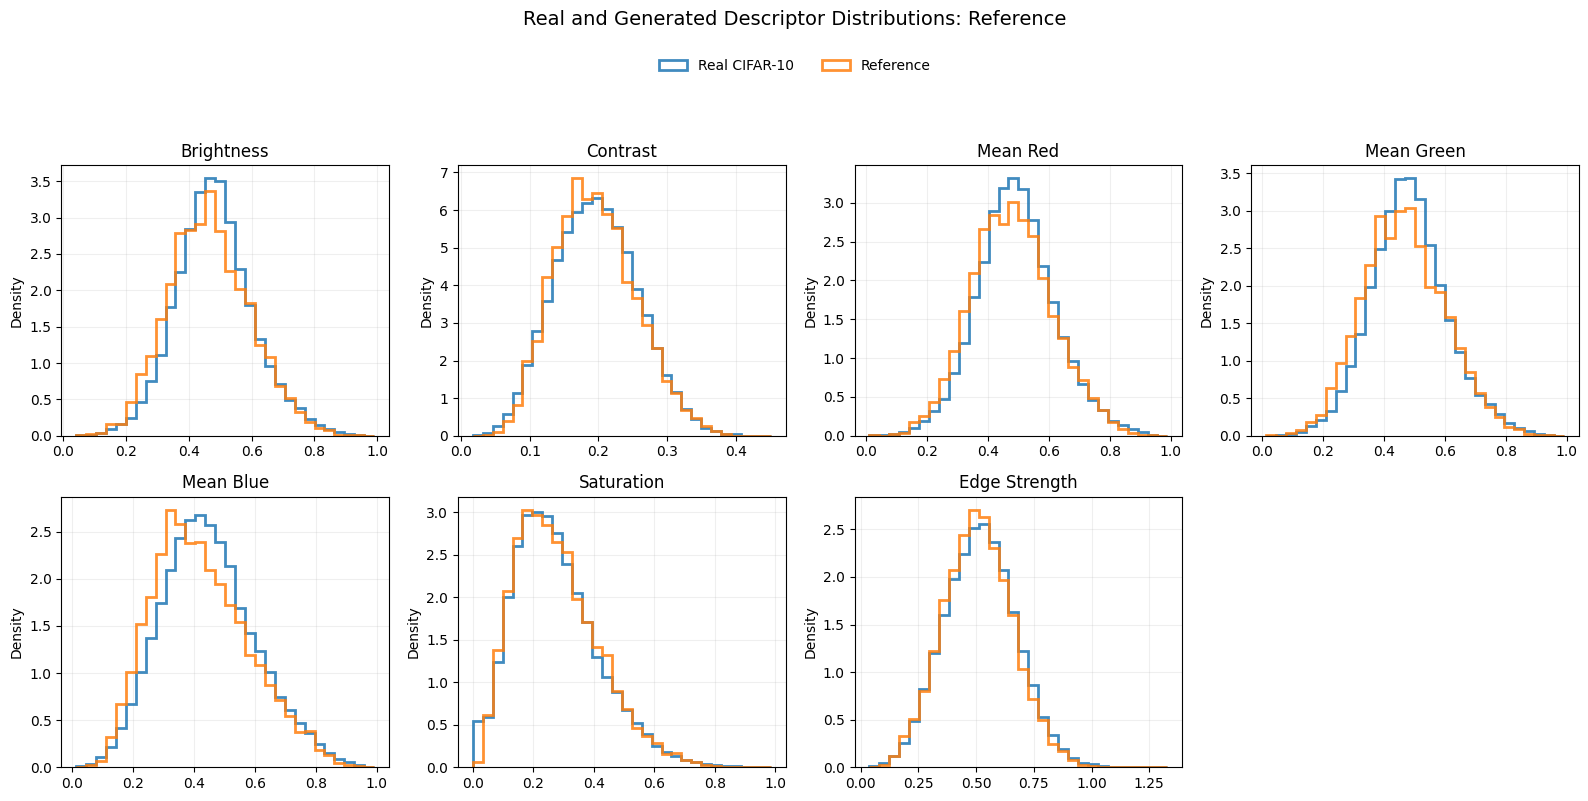

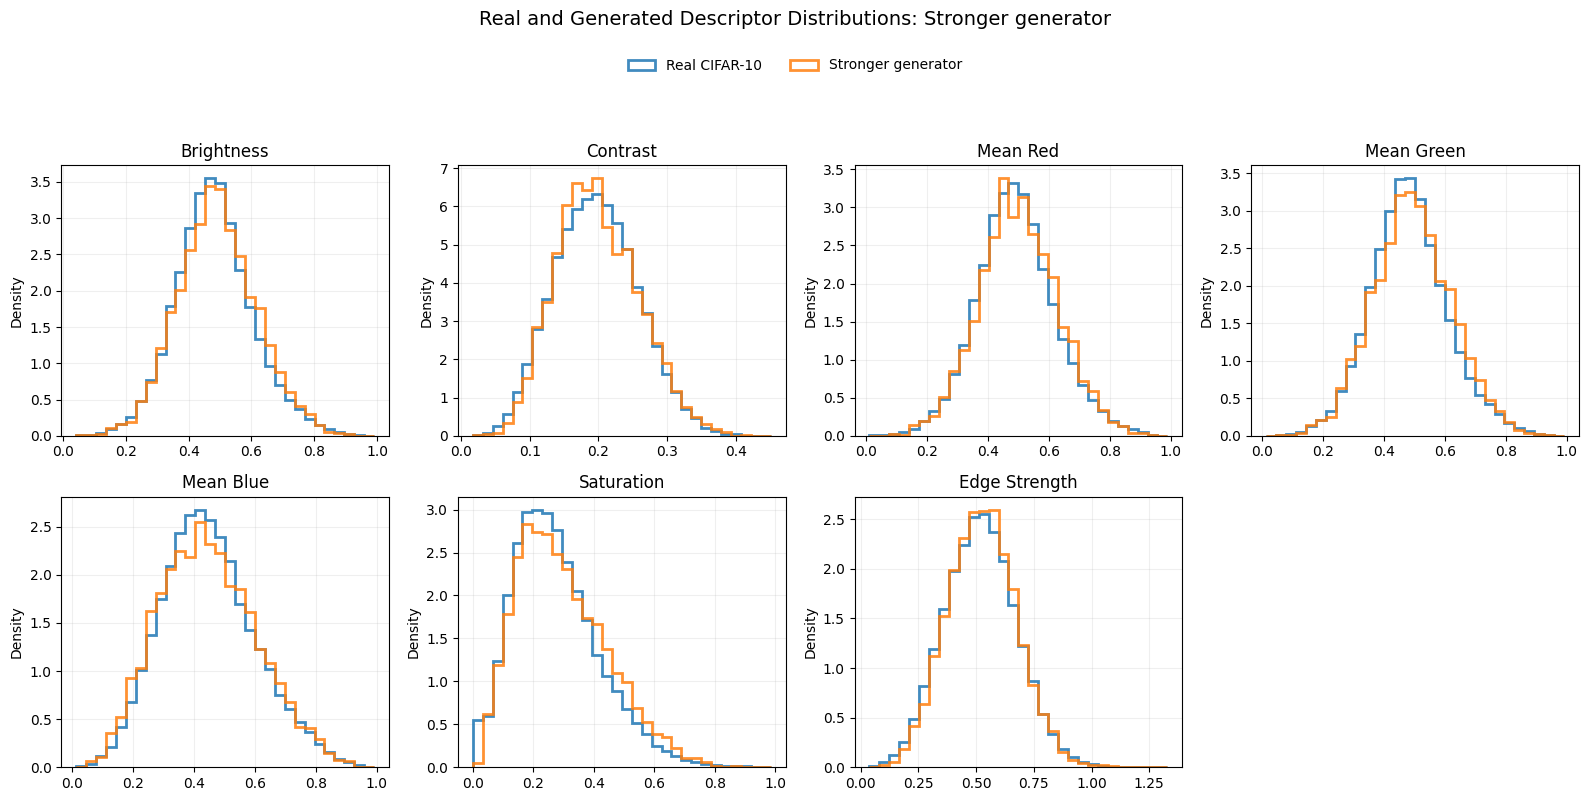

Reference descriptor plot: [local project directory]/grids/capacity_tier2_reference_descriptor_distributions.png
Candidate descriptor plot: [local project directory]/grids/capacity_tier2_stronger_generator_descriptor_distributions.png


In [112]:
capacity_reference_descriptor_plot_path = (
    GRIDS_DIR
    / (
        "capacity_tier2_reference_"
        "descriptor_distributions.png"
    )
)

capacity_candidate_descriptor_plot_path = (
    GRIDS_DIR
    / (
        "capacity_tier2_stronger_generator_"
        "descriptor_distributions.png"
    )
)


plot_descriptor_distributions(
    real_descriptors=real_descriptor_df,
    generated_descriptors=(
        capacity_reference_descriptor_df
    ),
    model_label="Reference",
    output_path=(
        capacity_reference_descriptor_plot_path
    ),
    bin_count=30,
)

plot_descriptor_distributions(
    real_descriptors=real_descriptor_df,
    generated_descriptors=(
        capacity_candidate_descriptor_df
    ),
    model_label="Stronger generator",
    output_path=(
        capacity_candidate_descriptor_plot_path
    ),
    bin_count=30,
)


print(
    "Reference descriptor plot:",
    capacity_reference_descriptor_plot_path,
)

print(
    "Candidate descriptor plot:",
    capacity_candidate_descriptor_plot_path,
)

**Interpretation**

Both capacity configurations broadly reproduce the real CIFAR-10 descriptor distributions without obvious severe compression.

The stronger generator is closer to the real mean for brightness, all three RGB-channel means and edge strength. The largest improvement is in mean blue intensity, where its absolute mean difference falls from `0.0256` to `0.0027`. Its brightness and colour-channel standard deviations are also generally close to the real reference.

The reference remains slightly closer for contrast, although the difference is negligible. Its main advantage is saturation: the stronger generator has a higher mean saturation of `0.2961`, compared with the real value of `0.2738`, and also shows a somewhat heavier upper saturation tail.

Descriptor evidence therefore modestly favours the stronger generator's brightness and RGB alignment, while identifying increased saturation as a caveat. These low-level descriptors support interpretation but do not independently establish better recognisability, semantic quality or model adoption.

#### Capacity Diversity and Repetition Comparison

The reference and stronger-generator checkpoints are compared using the canonical Section 6 cosine-diversity helper.

Each model supplies the same 5,000-image evaluation pool. Ten matched random subsets of 1,000 images are drawn from:

- the real CIFAR-10 training feature bank;
- the reference generated feature pool;
- the stronger-generator feature pool.

The same generated subset indices are used for both models within each repeat, preserving a paired comparison.

For every repeat, the analysis reports:

- mean pairwise cosine distance;
- median pairwise cosine distance;
- median and minimum nearest-neighbour distance;
- diversity relative to real CIFAR-10;
- near-duplicate rate using the real subset's first-percentile threshold.

Exact pixel duplicates are checked across each complete 5,000-image generated pool.

Repeated subsets are used because individual pairwise distances are not treated as independent observations. This analysis measures generated-to-generated diversity and repetition, not generated-to-training memorisation.

In [118]:
assert SECTION6_DIVERSITY_HELPER_READY
assert callable(
    compact_cosine_diversity_summary
)

assert capacity_full_eval_reference_features.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    FID_FEATURE_DIM,
)

assert capacity_full_eval_candidate_features.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    FID_FEATURE_DIM,
)

assert capacity_full_eval_reference_images.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    32,
    32,
    3,
)

assert capacity_full_eval_candidate_images.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    32,
    32,
    3,
)


capacity_real_diversity_rng = (
    np.random.default_rng(
        REAL_DIVERSITY_SEED
    )
)

capacity_generated_diversity_rng = (
    np.random.default_rng(
        GENERATED_DIVERSITY_SEED
    )
)

capacity_diversity_repeat_rows = []

# Retain the first repeat for the later
# nearest-neighbour distribution plot.
capacity_diversity_representative = None


for repeat_index in range(
    1,
    DIVERSITY_REPEATS + 1,
):
    real_indices = (
        capacity_real_diversity_rng.choice(
            len(real_fid_features),
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        capacity_generated_diversity_rng.choice(
            SELECTED_EVALUATION_SAMPLE_COUNT,
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    real_summary = (
        compact_cosine_diversity_summary(
            real_fid_features[
                real_indices
            ]
        )
    )

    reference_summary = (
        compact_cosine_diversity_summary(
            capacity_full_eval_reference_features[
                generated_indices
            ]
        )
    )

    candidate_summary = (
        compact_cosine_diversity_summary(
            capacity_full_eval_candidate_features[
                generated_indices
            ]
        )
    )

    near_duplicate_threshold = float(
        np.percentile(
            real_summary[
                "nearest_distances"
            ],
            NEAR_DUPLICATE_PERCENTILE,
        )
    )

    summaries = {
        "Real CIFAR-10": real_summary,
        "Reference": reference_summary,
        "Stronger generator": (
            candidate_summary
        ),
    }

    for configuration, summary in (
        summaries.items()
    ):
        if configuration == "Real CIFAR-10":
            diversity_ratio = 1.0
        else:
            diversity_ratio = float(
                summary[
                    "mean_pairwise_distance"
                ]
                / real_summary[
                    "mean_pairwise_distance"
                ]
            )

        near_duplicate_rate = float(
            np.mean(
                summary[
                    "nearest_distances"
                ]
                < near_duplicate_threshold
            )
            * 100.0
        )

        capacity_diversity_repeat_rows.append(
            {
                "Repeat": repeat_index,
                "Configuration": configuration,
                "Feature sample count": (
                    DIVERSITY_SUBSET_SIZE
                ),
                "Mean pairwise distance": (
                    summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Median pairwise distance": (
                    summary[
                        "median_pairwise_distance"
                    ]
                ),
                "Median nearest distance": (
                    summary[
                        "median_nearest_distance"
                    ]
                ),
                "Minimum nearest distance": (
                    summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-duplicate threshold": (
                    near_duplicate_threshold
                ),
                "Near-duplicate rate (%)": (
                    near_duplicate_rate
                ),
                "Diversity ratio to real": (
                    diversity_ratio
                ),
            }
        )

    if repeat_index == 1:
        capacity_diversity_representative = {
            "generated_indices": (
                generated_indices.copy()
            ),
            "real_nearest_distances": (
                real_summary[
                    "nearest_distances"
                ].copy()
            ),
            "reference_nearest_distances": (
                reference_summary[
                    "nearest_distances"
                ].copy()
            ),
            "candidate_nearest_distances": (
                candidate_summary[
                    "nearest_distances"
                ].copy()
            ),
            "near_duplicate_threshold": (
                near_duplicate_threshold
            ),
        }


capacity_diversity_repeats_df = (
    pd.DataFrame(
        capacity_diversity_repeat_rows
    )
)

assert len(
    capacity_diversity_repeats_df
) == (
    DIVERSITY_REPEATS * 3
)

assert (
    capacity_diversity_representative
    is not None
)

print(
    "Completed matched diversity repeats:",
    DIVERSITY_REPEATS,
)

Completed matched diversity repeats: 10


In [121]:
capacity_diversity_summary_df = (
    capacity_diversity_repeats_df
    .groupby(
        "Configuration",
        as_index=False,
    )
    .agg(
        mean_pairwise_distance_mean=(
            "Mean pairwise distance",
            "mean",
        ),
        mean_pairwise_distance_sd=(
            "Mean pairwise distance",
            "std",
        ),
        median_pairwise_distance_mean=(
            "Median pairwise distance",
            "mean",
        ),
        median_nearest_distance_mean=(
            "Median nearest distance",
            "mean",
        ),
        near_duplicate_rate_mean=(
            "Near-duplicate rate (%)",
            "mean",
        ),
        near_duplicate_rate_sd=(
            "Near-duplicate rate (%)",
            "std",
        ),
        diversity_ratio_mean=(
            "Diversity ratio to real",
            "mean",
        ),
        diversity_ratio_sd=(
            "Diversity ratio to real",
            "std",
        ),
    )
)


capacity_reference_flat_images = (
    capacity_full_eval_reference_images
    .reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

capacity_candidate_flat_images = (
    capacity_full_eval_candidate_images
    .reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

capacity_reference_unique_count = int(
    np.unique(
        capacity_reference_flat_images,
        axis=0,
    ).shape[0]
)

capacity_candidate_unique_count = int(
    np.unique(
        capacity_candidate_flat_images,
        axis=0,
    ).shape[0]
)

capacity_reference_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - capacity_reference_unique_count
)

capacity_candidate_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - capacity_candidate_unique_count
)

capacity_exact_duplicate_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Exact duplicates": (
                capacity_reference_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                capacity_reference_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
        {
            "Configuration": (
                "Stronger generator"
            ),
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Exact duplicates": (
                capacity_candidate_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                capacity_candidate_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
    ]
)


capacity_diversity_repeat_path = (
    HISTORIES_DIR
    / "capacity_tier2_diversity_repeats.csv"
)

capacity_diversity_summary_path = (
    HISTORIES_DIR
    / "capacity_tier2_diversity_summary.csv"
)

capacity_exact_duplicate_path = (
    HISTORIES_DIR
    / "capacity_tier2_exact_duplicates.csv"
)

capacity_diversity_repeats_df.to_csv(
    capacity_diversity_repeat_path,
    index=False,
)

capacity_diversity_summary_df.to_csv(
    capacity_diversity_summary_path,
    index=False,
)

capacity_exact_duplicate_df.to_csv(
    capacity_exact_duplicate_path,
    index=False,
)


display(
    capacity_diversity_summary_df.round(6)
)

display(
    capacity_exact_duplicate_df.round(6)
)


reference_diversity_ratios = (
    capacity_diversity_repeats_df.loc[
        capacity_diversity_repeats_df[
            "Configuration"
        ] == "Reference",
        "Diversity ratio to real",
    ]
    .to_numpy()
)

candidate_diversity_ratios = (
    capacity_diversity_repeats_df.loc[
        capacity_diversity_repeats_df[
            "Configuration"
        ] == "Stronger generator",
        "Diversity ratio to real",
    ]
    .to_numpy()
)

capacity_candidate_ratio_advantages = (
    np.abs(
        reference_diversity_ratios - 1.0
    )
    - np.abs(
        candidate_diversity_ratios - 1.0
    )
)

print(
    "Repeats where candidate diversity ratio "
    "was closer to real:",
    int(
        np.sum(
            capacity_candidate_ratio_advantages
            > 0
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Mean candidate improvement in absolute "
    "diversity-ratio error:",
    (
        f"{capacity_candidate_ratio_advantages.mean():.6f}"
    ),
)

print(
    "Repeat-level results saved:",
    capacity_diversity_repeat_path,
)

print(
    "Summary saved:",
    capacity_diversity_summary_path,
)

print(
    "Exact-duplicate results saved:",
    capacity_exact_duplicate_path,
)

print(
    "Protected test set remains unused."
)


del capacity_reference_flat_images
del capacity_candidate_flat_images

gc.collect()

,Configuration,mean_pairwise_distance_mean,mean_pairwise_distance_sd,median_pairwise_distance_mean,median_nearest_distance_mean,near_duplicate_rate_mean,near_duplicate_rate_sd,diversity_ratio_mean,diversity_ratio_sd
0,Real CIFAR-10,0.376167,0.002501,0.378124,0.195889,0.96,0.05164,1.000000,0.000000
1,Reference,0.351217,0.001768,0.349867,0.195930,0.00,0.00000,0.933711,0.007691
2,Stronger generator,0.351068,0.001803,0.349169,0.198089,0.00,0.00000,0.933309,0.006836


,Configuration,Image sample count,Exact duplicates,Exact-duplicate rate (%)
0,Reference,5000,0,0.0
1,Stronger generator,5000,0,0.0


Repeats where candidate diversity ratio was closer to real: 5 of 10
Mean candidate improvement in absolute diversity-ratio error: -0.000402
Repeat-level results saved: [local project directory]/histories/capacity_tier2_diversity_repeats.csv
Summary saved: [local project directory]/histories/capacity_tier2_diversity_summary.csv
Exact-duplicate results saved: [local project directory]/histories/capacity_tier2_exact_duplicates.csv
Protected test set remains unused.


0

#### Capacity Training-Trajectory Comparison

Training trajectories are shown for the reference and stronger-generator configurations under both training seeds.

This comparison establishes whether the capacity change produces consistent changes in adversarial balance across independent runs. Loss magnitudes are interpreted alongside generated-image evidence and are not used as direct quality scores.

In [128]:
capacity_selected_history_specs = [
    {
        "label": (
            "Reference, seed 42 "
            "(selected epoch 100)"
        ),
        "history_path": (
            HISTORIES_DIR
            / "G02_dcgan_seed42.csv"
        ),
    },
    {
        "label": (
            "Stronger generator, seed 42 "
            "(selected epoch 90)"
        ),
        "history_path": (
            HISTORIES_DIR
            / "G06_capacity_strongerG_seed42.csv"
        ),
    },
    {
        "label": (
            "Reference, seed 123 "
            "(selected epoch 90)"
        ),
        "history_path": (
            HISTORIES_DIR
            / "G02_dcgan_seed123.csv"
        ),
    },
    {
        "label": (
            "Stronger generator, seed 123 "
            "(selected epoch 100)"
        ),
        "history_path": (
            HISTORIES_DIR
            / "G06_capacity_strongerG_seed123.csv"
        ),
    },
]

capacity_training_trajectory_path = (
    GRIDS_DIR
    / "capacity_selected_training_trajectories.png"
)

plot_dcgan_history_comparison(
    history_specs=(
        capacity_selected_history_specs
    ),
    title=(
        "Capacity Comparison Across "
        "Training Seeds"
    ),
    output_path=(
        capacity_training_trajectory_path
    ),
)

print(
    "Capacity trajectory plot saved:",
    capacity_training_trajectory_path,
)

Capacity trajectory plot saved: [local project directory]/grids/capacity_selected_training_trajectories.png


**Interpretation**

All four capacity runs completed without non-finite behaviour or sustained oscillation.

The training seeds produced noticeably different early trajectories, especially during approximately the first 25 epochs. However, the reference and stronger-generator runs gradually entered a similar late-training regime.

Across both seeds:

- generator loss increased gradually as discriminator confidence strengthened;
- discriminator loss generally declined toward approximately `0.10`;
- mean real-image scores increased toward approximately `0.94`;
- mean generated-image scores declined toward approximately `0.06`.

The stronger generator did not consistently improve adversarial balance. Its seed-42 and seed-123 trajectories ultimately resemble the corresponding reference trajectories despite its larger capacity.

The trajectory evidence therefore indicates comparable late-training stability. It provides no stability veto against the stronger generator, but it also provides no independent adoption argument. Generated-image quality must remain the primary basis for the capacity decision.

#### Capacity Nearest-Neighbour Inspection

The first matched diversity repeat is used to inspect generated-to-generated nearest-neighbour distances.

The analysis includes:

- an empirical cumulative distribution of nearest-neighbour cosine distances;
- the real-data first-percentile near-duplicate threshold;
- the ten closest unique generated-image pairs for each capacity configuration.

The purpose is to check whether similar aggregate diversity scores conceal visibly repeated or near-identical outputs.

This remains a generated-to-generated repetition analysis. It is not the formal generated-to-training memorisation audit, which remains reserved for Notebook 4.

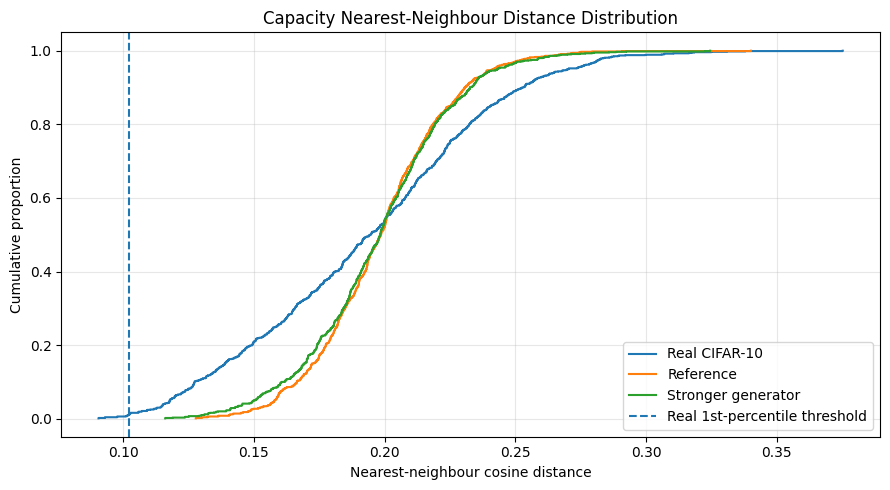

Saved nearest-distance plot: [local project directory]/grids/capacity_tier2_nearest_distance_ecdf.png
Near-duplicate threshold: 0.102227


In [130]:
capacity_nearest_distance_plot_path = (
    GRIDS_DIR
    / "capacity_tier2_nearest_distance_ecdf.png"
)

capacity_real_nearest_distances = (
    capacity_diversity_representative[
        "real_nearest_distances"
    ]
)

capacity_reference_nearest_distances = (
    capacity_diversity_representative[
        "reference_nearest_distances"
    ]
)

capacity_candidate_nearest_distances = (
    capacity_diversity_representative[
        "candidate_nearest_distances"
    ]
)

capacity_near_duplicate_threshold = float(
    capacity_diversity_representative[
        "near_duplicate_threshold"
    ]
)


capacity_real_sorted_distances = np.sort(
    capacity_real_nearest_distances
)

capacity_reference_sorted_distances = np.sort(
    capacity_reference_nearest_distances
)

capacity_candidate_sorted_distances = np.sort(
    capacity_candidate_nearest_distances
)


capacity_real_ecdf = np.arange(
    1,
    len(capacity_real_sorted_distances) + 1,
) / len(capacity_real_sorted_distances)

capacity_reference_ecdf = np.arange(
    1,
    len(capacity_reference_sorted_distances) + 1,
) / len(capacity_reference_sorted_distances)

capacity_candidate_ecdf = np.arange(
    1,
    len(capacity_candidate_sorted_distances) + 1,
) / len(capacity_candidate_sorted_distances)


plt.figure(figsize=(9, 5))

plt.step(
    capacity_real_sorted_distances,
    capacity_real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    capacity_reference_sorted_distances,
    capacity_reference_ecdf,
    where="post",
    label="Reference",
)

plt.step(
    capacity_candidate_sorted_distances,
    capacity_candidate_ecdf,
    where="post",
    label="Stronger generator",
)

plt.axvline(
    capacity_near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "Capacity Nearest-Neighbour Distance Distribution"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    capacity_nearest_distance_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved nearest-distance plot:",
    capacity_nearest_distance_plot_path,
)

print(
    "Near-duplicate threshold:",
    f"{capacity_near_duplicate_threshold:.6f}",
)

In [131]:
capacity_representative_indices = (
    capacity_diversity_representative[
        "generated_indices"
    ]
)

capacity_reference_pair_features = (
    capacity_full_eval_reference_features[
        capacity_representative_indices
    ]
)

capacity_candidate_pair_features = (
    capacity_full_eval_candidate_features[
        capacity_representative_indices
    ]
)

capacity_reference_pair_images = (
    capacity_full_eval_reference_images[
        capacity_representative_indices
    ]
)

capacity_candidate_pair_images = (
    capacity_full_eval_candidate_images[
        capacity_representative_indices
    ]
)


capacity_reference_feature_norms = np.maximum(
    np.linalg.norm(
        capacity_reference_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)

capacity_candidate_feature_norms = np.maximum(
    np.linalg.norm(
        capacity_candidate_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)


capacity_reference_normalised_features = (
    capacity_reference_pair_features
    / capacity_reference_feature_norms
)

capacity_candidate_normalised_features = (
    capacity_candidate_pair_features
    / capacity_candidate_feature_norms
)


capacity_reference_distance_matrix = np.clip(
    1.0
    - (
        capacity_reference_normalised_features
        @ capacity_reference_normalised_features.T
    ),
    0.0,
    2.0,
)

capacity_candidate_distance_matrix = np.clip(
    1.0
    - (
        capacity_candidate_normalised_features
        @ capacity_candidate_normalised_features.T
    ),
    0.0,
    2.0,
)

np.fill_diagonal(
    capacity_reference_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    capacity_candidate_distance_matrix,
    np.inf,
)

assert capacity_reference_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

assert capacity_candidate_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

print(
    "Matched nearest-neighbour distance matrices ready."
)

Matched nearest-neighbour distance matrices ready.


In [132]:
capacity_pair_configurations = [
    {
        "label": "Reference",
        "images": capacity_reference_pair_images,
        "distance_matrix": (
            capacity_reference_distance_matrix
        ),
        "output_path": (
            GRIDS_DIR
            / (
                "capacity_tier2_reference_"
                "most_similar_pairs.png"
            )
        ),
    },
    {
        "label": "Stronger generator",
        "images": capacity_candidate_pair_images,
        "distance_matrix": (
            capacity_candidate_distance_matrix
        ),
        "output_path": (
            GRIDS_DIR
            / (
                "capacity_tier2_stronger_generator_"
                "most_similar_pairs.png"
            )
        ),
    },
]


capacity_pair_summary_rows = []

for configuration in capacity_pair_configurations:
    label = configuration["label"]
    images = configuration["images"]
    distance_matrix = configuration[
        "distance_matrix"
    ]
    output_path = configuration[
        "output_path"
    ]

    nearest_indices = np.argmin(
        distance_matrix,
        axis=1,
    )

    unique_pair_distances = {}

    for image_index, neighbour_index in enumerate(
        nearest_indices
    ):
        pair = tuple(
            sorted(
                (
                    int(image_index),
                    int(neighbour_index),
                )
            )
        )

        pair_distance = float(
            distance_matrix[
                pair[0],
                pair[1],
            ]
        )

        if pair not in unique_pair_distances:
            unique_pair_distances[pair] = (
                pair_distance
            )

    most_similar_pairs = sorted(
        unique_pair_distances.items(),
        key=lambda item: item[1],
    )[:10]

    fig, axes = plt.subplots(
        5,
        4,
        figsize=(10, 13),
    )

    for pair_number, (
        pair,
        pair_distance,
    ) in enumerate(most_similar_pairs):
        row = pair_number // 2
        column = (
            pair_number % 2
        ) * 2

        first_index, second_index = pair

        axes[row, column].imshow(
            images[first_index]
        )

        axes[row, column].set_title(
            f"Pair {pair_number + 1}A",
            fontsize=9,
        )

        axes[row, column].axis("off")

        axes[row, column + 1].imshow(
            images[second_index]
        )

        axes[row, column + 1].set_title(
            (
                f"Pair {pair_number + 1}B\n"
                f"Distance: {pair_distance:.4f}"
            ),
            fontsize=9,
        )

        axes[row, column + 1].axis("off")

        capacity_pair_summary_rows.append(
            {
                "Configuration": label,
                "Pair": pair_number + 1,
                "First index": first_index,
                "Second index": second_index,
                "Cosine distance": pair_distance,
            }
        )

    fig.suptitle(
        f"{label} Most Similar Generated Pairs",
        fontsize=14,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.97)
    )

    fig.savefig(
        output_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved {label} pair figure:",
        output_path,
    )


capacity_closest_pair_summary_df = (
    pd.DataFrame(
        capacity_pair_summary_rows
    )
)

capacity_closest_pair_summary_path = (
    HISTORIES_DIR
    / "capacity_tier2_closest_pairs.csv"
)

capacity_closest_pair_summary_df.to_csv(
    capacity_closest_pair_summary_path,
    index=False,
)

display(
    capacity_closest_pair_summary_df.round(6)
)

print(
    "Closest-pair summary saved:",
    capacity_closest_pair_summary_path,
)

Saved Reference pair figure: [local project directory]/grids/capacity_tier2_reference_most_similar_pairs.png


Saved Stronger generator pair figure: [local project directory]/grids/capacity_tier2_stronger_generator_most_similar_pairs.png


,Configuration,Pair,First index,Second index,Cosine distance
0,Reference,1,75,424,0.127781
1,Reference,2,655,731,0.130089
2,Reference,3,268,688,0.132347
3,Reference,4,825,951,0.136353
4,Reference,5,471,764,0.140547
5,Reference,6,181,925,0.140833
6,Reference,7,393,968,0.142092
7,Reference,8,123,832,0.145035
8,Reference,9,778,917,0.145908
9,Reference,10,181,732,0.147621


Closest-pair summary saved: [local project directory]/histories/capacity_tier2_closest_pairs.csv


### 9.9 Capacity-Balance Decision

The capacity family compared the carried reference generator with a stronger generator using channels `288 → 144 → 72`.

Under training seed `42`, the stronger generator produced encouraging evidence:

- repeated development FID improved from `37.0260` to `35.3616`;
- strict manual scoring improved from `9` to `19` Clear images;
- Nonsense outputs fell from `16` to `7`;
- classifier-supported class coverage showed no regression;
- five of seven descriptor means moved closer to the real reference.

However, the improvement did not reproduce under training seed `123`.

| Configuration | Seed 42 repeated FID | Seed 123 repeated FID | Two-seed mean FID |
|---|---:|---:|---:|
| Reference | 37.0260 | 36.5838 | 36.8049 |
| Stronger generator | 35.3616 | 36.8507 | 36.1062 |

The stronger generator was `0.2669` worse under seed `123`. Its two-seed mean improvement was only `0.6987`, below the locked practical FID margin of `2.0`.

The remaining evaluation evidence did not establish another robust adoption basis:

- feature-space diversity was effectively tied;
- both models had zero exact and near-duplicate rates;
- closest-pair inspection showed a local cluster of similar red-car outputs for the stronger generator;
- classifier-supported coverage was effectively tied;
- late-training stability was comparable;
- the stronger generator showed increased saturation;
- generator parameter count increased by approximately 21%.

The stronger generator therefore provides a meaningful but seed-sensitive result rather than a confirmed improvement.

The original generator capacity is retained:

- generator channels: `256 → 128 → 64`;
- discriminator channels: `64 → 128 → 256`;
- generator parameters: `1,085,187`;
- discriminator parameters: `664,129`.

No further capacity model or rescue seed will be trained.

The capacity family is closed, and the protected CIFAR-10 test set remains unused.

In [133]:
def get_recorded_runtime_minutes(run_id):
    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    if not history_path.is_file():
        raise FileNotFoundError(
            history_path
        )

    history_df = pd.read_csv(
        history_path
    )

    if "epoch_time_seconds" not in history_df.columns:
        raise ValueError(
            f"Missing epoch_time_seconds: {history_path}"
        )

    return float(
        history_df[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )


capacity_reference_seed42_runtime = (
    get_recorded_runtime_minutes(
        "G02_dcgan_seed42"
    )
)

capacity_candidate_seed42_runtime = (
    get_recorded_runtime_minutes(
        "G06_capacity_strongerG_seed42"
    )
)

capacity_reference_seed123_runtime = (
    get_recorded_runtime_minutes(
        "G02_dcgan_seed123"
    )
)

capacity_candidate_seed123_runtime = (
    get_recorded_runtime_minutes(
        "G06_capacity_strongerG_seed123"
    )
)


capacity_parameter_increase_percent = (
    (
        1_312_995
        - 1_085_187
    )
    / 1_085_187
    * 100.0
)


capacity_final_evidence_df = pd.DataFrame(
    [
        {
            "Evidence": "Repeated FID, seed 42",
            "Reference": "37.0260",
            "Stronger generator": "35.3616",
            "Interpretation": (
                "Candidate better by 1.6644"
            ),
        },
        {
            "Evidence": "Repeated FID, seed 123",
            "Reference": "36.5838",
            "Stronger generator": "36.8507",
            "Interpretation": (
                "Reference better by 0.2669"
            ),
        },
        {
            "Evidence": "Two-seed mean FID",
            "Reference": "36.8049",
            "Stronger generator": "36.1062",
            "Interpretation": (
                "Candidate gain 0.6987, "
                "below 2.0 margin"
            ),
        },
        {
            "Evidence": (
                "Manual Clear / Marginal / Nonsense"
            ),
            "Reference": "9 / 75 / 16",
            "Stronger generator": "19 / 74 / 7",
            "Interpretation": (
                "Supports candidate at seed 42, "
                "but not decisive alone"
            ),
        },
        {
            "Evidence": (
                "Coverage JS divergence"
            ),
            "Reference": "0.0133",
            "Stronger generator": "0.0133",
            "Interpretation": "Tie",
        },
        {
            "Evidence": (
                "Dominant-class share"
            ),
            "Reference": "0.1882",
            "Stronger generator": "0.1740",
            "Interpretation": (
                "Slight candidate advantage"
            ),
        },
        {
            "Evidence": (
                "Descriptors closer to real mean"
            ),
            "Reference": "2 of 7",
            "Stronger generator": "5 of 7",
            "Interpretation": (
                "Candidate better overall, "
                "but oversaturated"
            ),
        },
        {
            "Evidence": (
                "Diversity ratio to real"
            ),
            "Reference": "0.933711",
            "Stronger generator": "0.933309",
            "Interpretation": "Practical tie",
        },
        {
            "Evidence": (
                "Median nearest distance"
            ),
            "Reference": "0.195930",
            "Stronger generator": "0.198089",
            "Interpretation": "Practical tie",
        },
        {
            "Evidence": (
                "Near / exact duplicate rate"
            ),
            "Reference": "0.00% / 0.00%",
            "Stronger generator": "0.00% / 0.00%",
            "Interpretation": "Tie",
        },
        {
            "Evidence": "Generator parameters",
            "Reference": "1,085,187",
            "Stronger generator": "1,312,995",
            "Interpretation": (
                f"Candidate +"
                f"{capacity_parameter_increase_percent:.2f}%"
            ),
        },
        {
            "Evidence": "Seed-42 runtime",
            "Reference": (
                f"{capacity_reference_seed42_runtime:.2f} min"
            ),
            "Stronger generator": (
                f"{capacity_candidate_seed42_runtime:.2f} min"
            ),
            "Interpretation": (
                "Reference is more compute-efficient"
            ),
        },
        {
            "Evidence": "Seed-123 runtime",
            "Reference": (
                f"{capacity_reference_seed123_runtime:.2f} min"
            ),
            "Stronger generator": (
                f"{capacity_candidate_seed123_runtime:.2f} min"
            ),
            "Interpretation": (
                "Supporting compute evidence"
            ),
        },
        {
            "Evidence": "Final capacity decision",
            "Reference": "Retained",
            "Stronger generator": "Rejected",
            "Interpretation": (
                "Improvement was not confirmed "
                "across training seeds"
            ),
        },
    ]
)


capacity_final_evidence_path = (
    HISTORIES_DIR
    / "capacity_final_evidence_and_decision.csv"
)

capacity_final_evidence_df.to_csv(
    capacity_final_evidence_path,
    index=False,
)

display(
    capacity_final_evidence_df
)


CAPACITY_SELECTED_CONFIGURATION = (
    "Reference capacity"
)

CAPACITY_SELECTED_GENERATOR_BUILDER = (
    build_dcgan_generator
)

CAPACITY_SELECTED_DISCRIMINATOR_BUILDER = (
    build_dcgan_discriminator
)

CAPACITY_SELECTED_GENERATOR_CHANNELS = (
    256,
    128,
    64,
)

CAPACITY_SELECTED_DISCRIMINATOR_CHANNELS = (
    64,
    128,
    256,
)

CAPACITY_SELECTED_GENERATOR_PARAMETERS = (
    1_085_187
)

CAPACITY_SELECTED_DISCRIMINATOR_PARAMETERS = (
    664_129
)

CAPACITY_FAMILY_CLOSED = True


assert (
    CAPACITY_SELECTED_GENERATOR_BUILDER
    is build_dcgan_generator
)

assert CAPACITY_FAMILY_CLOSED

print(
    "Capacity decision:",
    CAPACITY_SELECTED_CONFIGURATION,
)

print(
    "Final evidence saved:",
    capacity_final_evidence_path,
)

print(
    "No further capacity run is planned."
)

print(
    "Protected test set remains unused."
)

,Evidence,Reference,Stronger generator,Interpretation
0,"Repeated FID, seed 42",37.0260,35.3616,Candidate better by 1.6644
1,"Repeated FID, seed 123",36.5838,36.8507,Reference better by 0.2669
2,Two-seed mean FID,36.8049,36.1062,"Candidate gain 0.6987, below 2.0 margin"
3,Manual Clear / Marginal / Nonsense,9 / 75 / 16,19 / 74 / 7,"Supports candidate at seed 42, but not decisiv..."
4,Coverage JS divergence,0.0133,0.0133,Tie
5,Dominant-class share,0.1882,0.1740,Slight candidate advantage
6,Descriptors closer to real mean,2 of 7,5 of 7,"Candidate better overall, but oversaturated"
7,Diversity ratio to real,0.933711,0.933309,Practical tie
8,Median nearest distance,0.195930,0.198089,Practical tie
9,Near / exact duplicate rate,0.00% / 0.00%,0.00% / 0.00%,Tie


Capacity decision: Reference capacity
Final evidence saved: [local project directory]/histories/capacity_final_evidence_and_decision.csv
No further capacity run is planned.
Protected test set remains unused.


In [134]:
capacity_cleanup_names = [
    "capacity_full_eval_reference_images",
    "capacity_full_eval_candidate_images",
    "capacity_full_eval_reference_features",
    "capacity_full_eval_candidate_features",
    "capacity_reference_descriptor_df",
    "capacity_candidate_descriptor_df",
    "capacity_reference_pair_features",
    "capacity_candidate_pair_features",
    "capacity_reference_pair_images",
    "capacity_candidate_pair_images",
    "capacity_reference_normalised_features",
    "capacity_candidate_normalised_features",
    "capacity_reference_distance_matrix",
    "capacity_candidate_distance_matrix",
]

for variable_name in capacity_cleanup_names:
    if variable_name in globals():
        del globals()[variable_name]

_ = gc.collect()

print(
    "Temporary capacity evaluation pools removed."
)

print(
    "Saved results and selected settings remain available."
)

Temporary capacity evaluation pools removed.
Saved results and selected settings remain available.


---

## 10. Learning-Rate and TTUR Experiment

### 10.1 Purpose and Experimental Design

The completed capacity experiment retained the original DCGAN architecture and capacity. However, the training trajectories consistently showed a strong discriminator:

- discriminator loss generally approached approximately `0.10`;
- real-image scores approached approximately `0.94`;
- generated-image scores approached approximately `0.06`;
- generator loss increased throughout late training.

These values do not independently prove that the discriminator is too strong, because GAN losses do not directly measure image quality. They nevertheless justify testing whether the learning-rate relationship affects adversarial balance and generated-image quality.

This section treats shared learning-rate scale and two-time-scale update rule (TTUR) as one coherent adversarial-recipe family.

Three recipes are compared:

| Recipe | Generator learning rate | Discriminator learning rate | Relationship |
|---|---:|---:|---|
| Current reference | `2 × 10⁻⁴` | `2 × 10⁻⁴` | Balanced baseline |
| Lower balanced | `1 × 10⁻⁴` | `1 × 10⁻⁴` | Both networks learn more slowly |
| Generator-favoured TTUR | `2 × 10⁻⁴` | `1 × 10⁻⁴` | Generator rate is twice the discriminator rate |

The lower balanced recipe tests whether reducing the overall optimiser step scale improves stability or final image quality.

The generator-favoured TTUR recipe keeps the generator at the established baseline rate while reducing the discriminator rate. This tests whether easing discriminator dominance improves generator learning without slowing both networks.

All other factors remain unchanged:

- original generator and discriminator capacity;
- latent dimension `100`;
- batch size `64`;
- 100 epochs;
- `Conv2DTranspose` upsampling;
- Adam optimiser;
- `beta_1 = 0.5`;
- `beta_2 = 0.999`;
- one discriminator update per generator update;
- binary cross-entropy;
- no augmentation;
- full CIFAR-10 training distribution;
- fresh model and optimiser states;
- training seed `42`;
- checkpoints and fixed grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100.

The current reference is reused rather than retrained.

A recipe is not selected because its generator and discriminator losses appear numerically balanced. Selection uses generated-image quality, development FID, progression, stability, coverage, diversity, repetition, manual evidence and compute.

No official CIFAR-10 test image is used.

In [140]:
LR_TTUR_FAMILY_NAME = (
    "Learning rate and TTUR"
)

LR_TTUR_REFERENCE_RUN_ID = (
    REFERENCE_RUN_ID
)

LR_TTUR_REFERENCE_SELECTED_EPOCH = int(
    REFERENCE_SELECTED_EPOCHS[
        REFERENCE_RUN_ID
    ]
)

LR_TTUR_LOWER_BALANCED_RUN_ID = (
    "G07_recipe_lowerbalanced_seed42"
)

LR_TTUR_GENERATOR_FAVOURED_RUN_ID = (
    "G07_recipe_generatorfavoured_seed42"
)

LR_TTUR_TRAINING_SEED = PRIMARY_SEED
LR_TTUR_TARGET_EPOCHS = CURRENT_EPOCHS
LR_TTUR_BATCH_SIZE = CURRENT_BATCH_SIZE
LR_TTUR_LATENT_DIM = CURRENT_LATENT_DIM

LR_TTUR_BETA_1 = CURRENT_BETA_1
LR_TTUR_BETA_2 = CURRENT_BETA_2

LR_TTUR_REFERENCE_GENERATOR_LR = 2e-4
LR_TTUR_REFERENCE_DISCRIMINATOR_LR = 2e-4

LR_TTUR_LOWER_BALANCED_GENERATOR_LR = 1e-4
LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR = 1e-4

LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR = 2e-4
LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR = 1e-4

LR_TTUR_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

LR_TTUR_CHECKPOINT_INTERVAL = 10


assert LR_TTUR_REFERENCE_RUN_ID == (
    "G02_dcgan_seed42"
)

assert LR_TTUR_REFERENCE_SELECTED_EPOCH == 100
assert LR_TTUR_TRAINING_SEED == 42
assert LR_TTUR_TARGET_EPOCHS == 100
assert LR_TTUR_BATCH_SIZE == 64
assert LR_TTUR_LATENT_DIM == 100

assert LR_TTUR_BETA_1 == 0.5
assert LR_TTUR_BETA_2 == 0.999

assert (
    LR_TTUR_REFERENCE_GENERATOR_LR,
    LR_TTUR_REFERENCE_DISCRIMINATOR_LR,
) == (
    2e-4,
    2e-4,
)

assert (
    LR_TTUR_LOWER_BALANCED_GENERATOR_LR,
    LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR,
) == (
    1e-4,
    1e-4,
)

assert (
    LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR,
    LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR,
) == (
    2e-4,
    1e-4,
)

assert LR_TTUR_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

print(
    "Learning-rate and TTUR family locked."
)

print(
    "Reference reused:",
    LR_TTUR_REFERENCE_RUN_ID,
)

print(
    "New alternatives: 2"
)

Learning-rate and TTUR family locked.
Reference reused: G02_dcgan_seed42
New alternatives: 2


In [141]:
lr_ttur_family_plan_df = pd.DataFrame(
    [
        {
            "Order": 1,
            "Run ID": (
                LR_TTUR_REFERENCE_RUN_ID
            ),
            "Recipe": "Current reference",
            "Role": "Carried reference",
            "Training action": (
                "Reuse completed run"
            ),
            "Training seed": 42,
            "Generator LR": (
                LR_TTUR_REFERENCE_GENERATOR_LR
            ),
            "Discriminator LR": (
                LR_TTUR_REFERENCE_DISCRIMINATOR_LR
            ),
            "LR relationship": "1G:1D",
            "Epoch budget": 100,
            "Selected epoch": (
                LR_TTUR_REFERENCE_SELECTED_EPOCH
            ),
        },
        {
            "Order": 2,
            "Run ID": (
                LR_TTUR_LOWER_BALANCED_RUN_ID
            ),
            "Recipe": "Lower balanced",
            "Role": "New alternative",
            "Training action": "Train or resume",
            "Training seed": 42,
            "Generator LR": (
                LR_TTUR_LOWER_BALANCED_GENERATOR_LR
            ),
            "Discriminator LR": (
                LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR
            ),
            "LR relationship": "1G:1D",
            "Epoch budget": 100,
            "Selected epoch": "Pending",
        },
        {
            "Order": 3,
            "Run ID": (
                LR_TTUR_GENERATOR_FAVOURED_RUN_ID
            ),
            "Recipe": (
                "Generator-favoured TTUR"
            ),
            "Role": "New alternative",
            "Training action": "Train or resume",
            "Training seed": 42,
            "Generator LR": (
                LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
            ),
            "Discriminator LR": (
                LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
            ),
            "LR relationship": "2G:1D",
            "Epoch budget": 100,
            "Selected epoch": "Pending",
        },
    ]
)

display(
    lr_ttur_family_plan_df
)


LR_TTUR_FAMILY_CONFIGURATIONS = [
    {
        "run_id": (
            LR_TTUR_LOWER_BALANCED_RUN_ID
        ),
        "configuration_label": (
            "DCGAN Lower Balanced "
            "Learning Rate"
        ),
        "main_change": (
            "Generator and discriminator "
            "learning rates reduced from "
            "2e-4 to 1e-4"
        ),
        "training_seed": (
            LR_TTUR_TRAINING_SEED
        ),
        "latent_dim": (
            LR_TTUR_LATENT_DIM
        ),
        "batch_size": (
            LR_TTUR_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            LR_TTUR_LOWER_BALANCED_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR
        ),
        "beta_1": LR_TTUR_BETA_1,
        "beta_2": LR_TTUR_BETA_2,
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "configuration_label": (
            "DCGAN Generator-Favoured TTUR"
        ),
        "main_change": (
            "Generator learning rate retained "
            "at 2e-4 while discriminator "
            "learning rate reduced to 1e-4"
        ),
        "training_seed": (
            LR_TTUR_TRAINING_SEED
        ),
        "latent_dim": (
            LR_TTUR_LATENT_DIM
        ),
        "batch_size": (
            LR_TTUR_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
        "beta_1": LR_TTUR_BETA_1,
        "beta_2": LR_TTUR_BETA_2,
    },
]


assert len(
    LR_TTUR_FAMILY_CONFIGURATIONS
) == 2

assert len(
    {
        configuration["run_id"]
        for configuration
        in LR_TTUR_FAMILY_CONFIGURATIONS
    }
) == 2

for configuration in (
    LR_TTUR_FAMILY_CONFIGURATIONS
):
    missing_keys = [
        key
        for key
        in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
        if key not in configuration
    ]

    assert not missing_keys, (
        f"Missing configuration keys: "
        f"{missing_keys}"
    )

assert {
    (
        configuration[
            "generator_learning_rate"
        ],
        configuration[
            "discriminator_learning_rate"
        ],
    )
    for configuration
    in LR_TTUR_FAMILY_CONFIGURATIONS
} == {
    (1e-4, 1e-4),
    (2e-4, 1e-4),
}

print(
    "Two new adversarial recipes declared."
)

print(
    "The completed reference is not included "
    "in the training list."
)

,Order,Run ID,Recipe,Role,Training action,Training seed,Generator LR,Discriminator LR,LR relationship,Epoch budget,Selected epoch
0,1,G02_dcgan_seed42,Current reference,Carried reference,Reuse completed run,42,0.0002,0.0002,1G:1D,100,100
1,2,G07_recipe_lowerbalanced_seed42,Lower balanced,New alternative,Train or resume,42,0.0001,0.0001,1G:1D,100,Pending
2,3,G07_recipe_generatorfavoured_seed42,Generator-favoured TTUR,New alternative,Train or resume,42,0.0002,0.0001,2G:1D,100,Pending


Two new adversarial recipes declared.
The completed reference is not included in the training list.


In [142]:
keras.backend.clear_session()

reset_run_seed(
    LR_TTUR_TRAINING_SEED
)

lr_ttur_probe_generator = (
    build_dcgan_generator(
        LR_TTUR_LATENT_DIM
    )
)

lr_ttur_probe_discriminator = (
    build_dcgan_discriminator()
)

assert (
    lr_ttur_probe_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    lr_ttur_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

lr_ttur_probe_noise = make_stateless_noise(
    sample_count=8,
    latent_dim=LR_TTUR_LATENT_DIM,
    seed=1707,
)

lr_ttur_probe_images = (
    lr_ttur_probe_generator(
        lr_ttur_probe_noise,
        training=False,
    )
)

lr_ttur_probe_scores = (
    lr_ttur_probe_discriminator(
        lr_ttur_probe_images,
        training=False,
    )
)

assert lr_ttur_probe_images.shape == (
    8,
    32,
    32,
    3,
)

assert lr_ttur_probe_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    lr_ttur_probe_images.numpy()
).all()

assert np.isfinite(
    lr_ttur_probe_scores.numpy()
).all()

print(
    "Generator parameters:",
    lr_ttur_probe_generator.count_params(),
)

print(
    "Discriminator parameters:",
    lr_ttur_probe_discriminator.count_params(),
)

print(
    "Inherited architecture and output "
    "contracts validated."
)

print(
    "Only the declared learning rates differ."
)


del lr_ttur_probe_generator
del lr_ttur_probe_discriminator
del lr_ttur_probe_noise
del lr_ttur_probe_images
del lr_ttur_probe_scores

keras.backend.clear_session()
_ = gc.collect()

Generator parameters: 1085187
Discriminator parameters: 664129
Inherited architecture and output contracts validated.
Only the declared learning rates differ.


In [143]:
lr_ttur_training_df = run_dcgan_family(
    family_name=(
        LR_TTUR_FAMILY_NAME
    ),
    configurations=(
        LR_TTUR_FAMILY_CONFIGURATIONS
    ),
    training_images=x_train_gan,
    target_epochs=(
        LR_TTUR_TARGET_EPOCHS
    ),
    checkpoint_root=CHECKPOINTS_DIR,
    weights_dir=WEIGHTS_DIR,
    histories_dir=HISTORIES_DIR,
    grids_dir=GRIDS_DIR,
    milestone_epochs=(
        LR_TTUR_MILESTONE_EPOCHS
    ),
    checkpoint_interval=(
        LR_TTUR_CHECKPOINT_INTERVAL
    ),
    fixed_grid_seed=(
        FIXED_PROGRESSION_SEED
    ),
    max_to_keep=3,
)

display(
    lr_ttur_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

print(
    "Learning-rate and TTUR training "
    "calls completed."
)

print(
    "The current reference was reused "
    "without retraining."
)

print(
    "No checkpoint selection or recipe "
    "decision has been performed."
)

print(
    "Protected test set remains unused."
)

Declared family: Learning rate and TTUR


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G07_recipe_lowerbalanced_seed42,DCGAN Lower Balanced Learning Rate,Generator and discriminator learning rates red...,42,100,64,0.0001,0.0001,0.5,0.999
1,2,G07_recipe_generatorfavoured_seed42,DCGAN Generator-Favoured TTUR,Generator learning rate retained at 2e-4 while...,42,100,64,0.0002,0.0001,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/2
Run ID: G07_recipe_lowerbalanced_seed42
Configuration: DCGAN Lower Balanced Learning Rate
Main change: Generator and discriminator learning rates reduced from 2e-4 to 1e-4
Training new run G07_recipe_lowerbalanced_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.3700 | D loss: 0.0547 | Real: 0.9633 | Fake: 0.0422 | Time: 16.7s
Epoch 002/100 | G loss: 1.4684 | D loss: 0.1767 | Real: 0.8671 | Fake: 0.1267 | Time: 12.7s
Epoch 003/100 | G loss: 1.8755 | D loss: 0.2519 | Real: 0.8068 | Fake: 0.1884 | Time: 12.8s
Epoch 004/100 | G loss: 2.5828 | D loss: 0.1774 | Real: 0.8588 | Fake: 0.1369 | Time: 12.9s
Epoch 005/100 | G loss: 2.4151 | D loss: 0.1186 | Real: 0.9031 | Fake: 0.0962 | Time: 12.6s
Epoch 006/100 | G loss: 2.3046 | D loss: 0.1086 | Real: 0.9159 | Fake: 0.0822 | Time: 12.8s
Epoch 007/100 | G loss: 2.4013 | D loss: 0.1362 | Real: 0.8936 | Fake: 0.1049 | Time: 

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G07_recipe_lowerbalanced_seed42,DCGAN Lower Balanced Learning Rate,trained_new,100,78200,78200,1085187,664129,21.1535
1,G07_recipe_generatorfavoured_seed42,DCGAN Generator-Favoured TTUR,trained_new,100,78200,78200,1085187,664129,21.2364


Learning-rate and TTUR training calls completed.
The current reference was reused without retraining.
No checkpoint selection or recipe decision has been performed.
Protected test set remains unused.


In [51]:
# Recreate the completed learning-rate/TTUR
# family declarations in fresh runtime.

LR_TTUR_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

LR_TTUR_LOWER_BALANCED_RUN_ID = (
    "G07_recipe_lowerbalanced_seed42"
)

LR_TTUR_GENERATOR_FAVOURED_RUN_ID = (
    "G07_recipe_generatorfavoured_seed42"
)


LR_TTUR_REFERENCE_GENERATOR_LR = 2e-4
LR_TTUR_REFERENCE_DISCRIMINATOR_LR = 2e-4

LR_TTUR_LOWER_BALANCED_GENERATOR_LR = 1e-4
LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR = 1e-4

LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR = 2e-4
LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR = 1e-4


LR_TTUR_BATCH_SIZE = 64
LR_TTUR_TARGET_EPOCHS = 100

LR_TTUR_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)


assert LR_TTUR_REFERENCE_RUN_ID == (
    "G02_dcgan_seed42"
)

assert LR_TTUR_LOWER_BALANCED_RUN_ID == (
    "G07_recipe_lowerbalanced_seed42"
)

assert LR_TTUR_GENERATOR_FAVOURED_RUN_ID == (
    "G07_recipe_generatorfavoured_seed42"
)

assert LR_TTUR_BATCH_SIZE == 64
assert LR_TTUR_TARGET_EPOCHS == 100

assert LR_TTUR_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

print(
    "Learning-rate/TTUR evaluation "
    "declarations restored."
)

Learning-rate/TTUR evaluation declarations restored.


### 10.2 Training Completion and Trajectory Diagnostics

Both new learning-rate recipes completed the full 100-epoch training budget. Before evaluating generated-image quality, this section verifies the persisted training artifacts and compares their complete trajectories against the reused reference recipe.

The comparison covers:

- generator loss;
- discriminator loss;
- mean discriminator score on real images;
- mean discriminator score on generated images;
- late-training variability;
- optimiser-update exposure;
- recorded runtime.

The trajectories help diagnose instability, oscillation, collapse and changes in adversarial balance. They do not directly measure generated-image quality, so no recipe or checkpoint is selected from these signals alone.

The three recipes are:

| Recipe | Generator learning rate | Discriminator learning rate |
|---|---:|---:|
| Current reference | `2 × 10⁻⁴` | `2 × 10⁻⁴` |
| Lower balanced | `1 × 10⁻⁴` | `1 × 10⁻⁴` |
| Generator-favoured TTUR | `2 × 10⁻⁴` | `1 × 10⁻⁴` |

All recipes use the same architecture, latent dimension, batch size, optimiser momentum, update ratio, data distribution and 100-epoch budget.

No official CIFAR-10 test image is used.

In [52]:
required_lr_ttur_trajectory_objects = [
    "LR_TTUR_REFERENCE_RUN_ID",
    "LR_TTUR_LOWER_BALANCED_RUN_ID",
    "LR_TTUR_GENERATOR_FAVOURED_RUN_ID",
    "LR_TTUR_REFERENCE_GENERATOR_LR",
    "LR_TTUR_REFERENCE_DISCRIMINATOR_LR",
    "LR_TTUR_LOWER_BALANCED_GENERATOR_LR",
    "LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR",
    "LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR",
    "LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR",
    "LR_TTUR_BATCH_SIZE",
    "LR_TTUR_TARGET_EPOCHS",
    "LR_TTUR_MILESTONE_EPOCHS",
    "HISTORIES_DIR",
    "WEIGHTS_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_trajectory_objects = [
    name
    for name in required_lr_ttur_trajectory_objects
    if name not in globals()
]

assert not missing_lr_ttur_trajectory_objects, (
    "Incomplete learning-rate and TTUR "
    "setup:\n"
    + "\n".join(
        missing_lr_ttur_trajectory_objects
    )
)


LR_TTUR_HISTORY_SPECS = [
    {
        "run_id": LR_TTUR_REFERENCE_RUN_ID,
        "label": (
            "Reference: G 2e-4, D 2e-4"
        ),
        "generator_lr": (
            LR_TTUR_REFERENCE_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_REFERENCE_DISCRIMINATOR_LR
        ),
    },
    {
        "run_id": (
            LR_TTUR_LOWER_BALANCED_RUN_ID
        ),
        "label": (
            "Lower balanced: G 1e-4, D 1e-4"
        ),
        "generator_lr": (
            LR_TTUR_LOWER_BALANCED_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR
        ),
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "label": (
            "Generator-favoured: "
            "G 2e-4, D 1e-4"
        ),
        "generator_lr": (
            LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
    },
]


LR_TTUR_TRAJECTORY_COLUMNS = [
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

LR_TTUR_TRAIN_IMAGE_COUNT = 50_000

LR_TTUR_BATCHES_PER_EPOCH = int(
    np.ceil(
        LR_TTUR_TRAIN_IMAGE_COUNT
        / LR_TTUR_BATCH_SIZE
    )
)

LR_TTUR_EXPECTED_UPDATES = (
    LR_TTUR_BATCHES_PER_EPOCH
    * LR_TTUR_TARGET_EPOCHS
)

LR_TTUR_TRAJECTORY_OUTPUT_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "trajectory_comparison.png"
    )
)

LR_TTUR_TRAJECTORY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "trajectory_summary.csv"
    )
)


assert len(LR_TTUR_HISTORY_SPECS) == 3

assert len(
    {
        specification["run_id"]
        for specification
        in LR_TTUR_HISTORY_SPECS
    }
) == 3

assert LR_TTUR_BATCH_SIZE == 64
assert LR_TTUR_TARGET_EPOCHS == 100

assert LR_TTUR_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert LR_TTUR_BATCHES_PER_EPOCH == 782
assert LR_TTUR_EXPECTED_UPDATES == 78_200


lr_ttur_history_dfs = {}
lr_ttur_trajectory_summary_rows = []


for specification in LR_TTUR_HISTORY_SPECS:
    run_id = specification["run_id"]
    label = specification["label"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    assert history_path.is_file(), (
        f"Missing history CSV:\n"
        f"{history_path}"
    )

    history_df = pd.read_csv(
        history_path
    )

    required_history_columns = [
        "epoch",
        *LR_TTUR_TRAJECTORY_COLUMNS,
    ]

    missing_history_columns = [
        column
        for column in required_history_columns
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{run_id} is missing history "
        f"columns:\n"
        + "\n".join(
            missing_history_columns
        )
    )

    assert len(history_df) == (
        LR_TTUR_TARGET_EPOCHS
    ), (
        f"{run_id} has "
        f"{len(history_df)} history rows, "
        f"expected "
        f"{LR_TTUR_TARGET_EPOCHS}."
    )

    observed_epochs = (
        history_df["epoch"]
        .to_numpy(dtype=np.int64)
    )

    expected_epochs = np.arange(
        1,
        LR_TTUR_TARGET_EPOCHS + 1,
        dtype=np.int64,
    )

    assert np.array_equal(
        observed_epochs,
        expected_epochs,
    ), (
        f"{run_id} does not contain exact "
        "epochs 1 through 100."
    )

    assert not history_df[
        required_history_columns
    ].isna().any().any(), (
        f"{run_id} contains missing "
        "history values."
    )

    assert np.isfinite(
        history_df[
            LR_TTUR_TRAJECTORY_COLUMNS
        ].to_numpy(dtype=np.float64)
    ).all(), (
        f"{run_id} contains non-finite "
        "training values."
    )


    # Verify the ten fixed-seed progression grids.
    progression_grid_paths = [
        (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )
        for epoch in range(
            10,
            LR_TTUR_TARGET_EPOCHS + 1,
            10,
        )
    ]

    missing_progression_grids = [
        str(path)
        for path in progression_grid_paths
        if not path.is_file()
    ]

    assert not missing_progression_grids, (
        f"{run_id} is missing progression "
        "grids:\n"
        + "\n".join(
            missing_progression_grids
        )
    )


    # Generator milestone weights are the
    # formal checkpoint-selection artifacts.
    milestone_generator_paths = [
        (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )
        for epoch in (
            LR_TTUR_MILESTONE_EPOCHS
        )
    ]

    missing_milestone_generator_weights = [
        str(path)
        for path in milestone_generator_paths
        if not path.is_file()
    ]

    assert not (
        missing_milestone_generator_weights
    ), (
        f"{run_id} is missing milestone "
        "generator weights:\n"
        + "\n".join(
            missing_milestone_generator_weights
        )
    )


    lr_ttur_history_dfs[label] = (
        history_df.copy()
    )

    late_history_df = history_df.loc[
        history_df["epoch"] >= 81
    ].copy()

    assert len(late_history_df) == 20


    lr_ttur_trajectory_summary_rows.append(
        {
            "Run ID": run_id,
            "Recipe": label,
            "Generator LR": (
                specification[
                    "generator_lr"
                ]
            ),
            "Discriminator LR": (
                specification[
                    "discriminator_lr"
                ]
            ),
            "Epochs": len(history_df),
            "Batches per epoch": (
                LR_TTUR_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Training time minutes": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Late G loss mean": float(
                late_history_df[
                    "generator_loss"
                ].mean()
            ),
            "Late G loss SD": float(
                late_history_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Late D loss mean": float(
                late_history_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late D loss SD": float(
                late_history_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Late real score mean": float(
                late_history_df[
                    "real_score"
                ].mean()
            ),
            "Late real score SD": float(
                late_history_df[
                    "real_score"
                ].std(ddof=1)
            ),
            "Late fake score mean": float(
                late_history_df[
                    "fake_score"
                ].mean()
            ),
            "Late fake score SD": float(
                late_history_df[
                    "fake_score"
                ].std(ddof=1)
            ),
            "Late score separation": float(
                (
                    late_history_df[
                        "real_score"
                    ]
                    - late_history_df[
                        "fake_score"
                    ]
                ).mean()
            ),
        }
    )


lr_ttur_trajectory_summary_df = (
    pd.DataFrame(
        lr_ttur_trajectory_summary_rows
    )
)

lr_ttur_trajectory_summary_df.to_csv(
    LR_TTUR_TRAJECTORY_SUMMARY_PATH,
    index=False,
)


metric_plot_specs = [
    (
        "generator_loss",
        "Generator Loss",
        "Binary cross-entropy",
    ),
    (
        "discriminator_loss",
        "Discriminator Loss",
        "Binary cross-entropy",
    ),
    (
        "real_score",
        "Mean Real-Image Score",
        "Mean discriminator output",
    ),
    (
        "fake_score",
        "Mean Generated-Image Score",
        "Mean discriminator output",
    ),
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
)

for axis, (
    metric_column,
    metric_title,
    y_label,
) in zip(
    axes.flat,
    metric_plot_specs,
):
    for label, history_df in (
        lr_ttur_history_dfs.items()
    ):
        axis.plot(
            history_df["epoch"],
            history_df[metric_column],
            label=label,
            linewidth=1.5,
        )

    axis.set_title(
        metric_title
    )

    axis.set_xlabel(
        "Epoch"
    )

    axis.set_ylabel(
        y_label
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend(
        fontsize=8
    )


plt.suptitle(
    "Learning-Rate and TTUR Training Trajectories",
    fontsize=15,
    y=0.995,
)

plt.tight_layout(
    rect=(0, 0, 1, 0.97)
)

plt.savefig(
    LR_TTUR_TRAJECTORY_OUTPUT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()


display(
    lr_ttur_trajectory_summary_df.round(4)
)


print(
    "All three 100-epoch histories and "
    "formal training artifacts were verified."
)

print(
    "Batches per epoch:",
    LR_TTUR_BATCHES_PER_EPOCH,
)

print(
    "Updates per network:",
    LR_TTUR_EXPECTED_UPDATES,
)

print(
    "Trajectory figure saved:"
)

print(
    LR_TTUR_TRAJECTORY_OUTPUT_PATH
)

print(
    "Late-training summary saved:"
)

print(
    LR_TTUR_TRAJECTORY_SUMMARY_PATH
)

print(
    "No image-quality or checkpoint "
    "decision has been made from "
    "training trajectories alone."
)

print(
    "Protected test set remains unused."
)

,Run ID,Recipe,Generator LR,Discriminator LR,Epochs,Batches per epoch,Generator updates,Discriminator updates,Training time minutes,Late G loss mean,Late G loss SD,Late D loss mean,Late D loss SD,Late real score mean,Late real score SD,Late fake score mean,Late fake score SD,Late score separation
0,G02_dcgan_seed42,"Reference: G 2e-4, D 2e-4",0.0002,0.0002,100,782,78200,78200,19.4674,4.6590,0.1529,0.1044,0.0217,0.9359,0.0087,0.0639,0.0087,0.8720
1,G07_recipe_lowerbalanced_seed42,"Lower balanced: G 1e-4, D 1e-4",0.0001,0.0001,100,782,78200,78200,21.1535,4.0814,0.1479,0.1099,0.0202,0.9268,0.0080,0.0729,0.0079,0.8539
2,G07_recipe_generatorfavoured_seed42,"Generator-favoured: G 2e-4, D 1e-4",0.0002,0.0001,100,782,78200,78200,21.2364,4.1193,0.1128,0.1130,0.0155,0.9268,0.0055,0.0729,0.0055,0.8539


All three 100-epoch histories and formal training artifacts were verified.
Batches per epoch: 782
Updates per network: 78200
Trajectory figure saved:
[local project directory]/grids/G07_learning_rate_ttur_trajectory_comparison.png
Late-training summary saved:
[local project directory]/histories/learning_rate_ttur_trajectory_summary.csv
No image-quality or checkpoint decision has been made from training trajectories alone.
Protected test set remains unused.


#### Training-Trajectory Findings

All three recipes completed 100 epochs with finite histories, equal update exposure and complete persisted artifacts.

The current reference retained the strongest late discriminator separation, with a mean real score of `0.9359`, mean generated score of `0.0639` and score separation of `0.8720` during epochs 81–100.

Both lower-discriminator-rate alternatives reduced the late score separation slightly to `0.8539`. This confirms that the learning-rate changes affected adversarial balance, although the difference became relatively small by late training.

The generator-favoured TTUR recipe produced the clearest early reduction in discriminator dominance. Its discriminator loss and generated-image scores remained higher during early training, but its trajectories gradually converged toward those of the lower-balanced recipe.

The lower-balanced recipe showed a sharper early transition and stronger short-term oscillation around epochs 10–25. However, it later stabilised and did not exhibit non-finite values or clear collapse.

The two new recipes required approximately 21.2 minutes each, compared with approximately 19.5 minutes for the reference. The alternatives therefore did not provide a compute advantage.

No recipe is rejected from the training diagnostics alone. Both alternatives advance to fixed-grid milestone review and development FID evaluation at epochs 50, 70, 90 and 100. Image quality and checkpoint selection are not inferred from losses alone.

In [55]:
LR_TTUR_VISUAL_EPOCHS = (
    50,
    70,
    90,
    100,
)

LR_TTUR_VISUAL_SPECS = [
    {
        "run_id": LR_TTUR_REFERENCE_RUN_ID,
        "label": "Reference\nG 2e-4, D 2e-4",
    },
    {
        "run_id": LR_TTUR_LOWER_BALANCED_RUN_ID,
        "label": "Lower balanced\nG 1e-4, D 1e-4",
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "label": "Generator-favoured\nG 2e-4, D 1e-4",
    },
]

LR_TTUR_MILESTONE_GRID_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "milestone_grid_comparison.png"
    )
)

fig, axes = plt.subplots(
    nrows=len(LR_TTUR_VISUAL_SPECS),
    ncols=len(LR_TTUR_VISUAL_EPOCHS),
    figsize=(16, 12),
)

for row_index, specification in enumerate(
    LR_TTUR_VISUAL_SPECS
):
    run_id = specification["run_id"]

    for column_index, epoch in enumerate(
        LR_TTUR_VISUAL_EPOCHS
    ):
        grid_path = (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )

        assert grid_path.is_file(), (
            f"Missing grid:\n{grid_path}"
        )

        grid_image = mpimg.imread(
            grid_path
        )

        axis = axes[
            row_index,
            column_index,
        ]

        axis.imshow(
            grid_image
        )

        axis.axis(
            "off"
        )

        if row_index == 0:
            axis.set_title(
                f"Epoch {epoch}",
                fontsize=12,
            )

        if column_index == 0:
            axis.text(
                -0.06,
                0.5,
                specification["label"],
                transform=axis.transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=11,
            )

plt.suptitle(
    "Learning-Rate and TTUR Fixed-Seed Milestone Progression",
    fontsize=15,
    y=0.995,
)

plt.tight_layout(
    rect=(0.03, 0, 1, 0.97)
)

plt.savefig(
    LR_TTUR_MILESTONE_GRID_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Milestone progression comparison saved:"
)

print(
    LR_TTUR_MILESTONE_GRID_PATH
)

print(
    "Review recognisability, diversity, "
    "repetition, colour balance and any "
    "late deterioration before checkpoint "
    "selection."
)

Milestone progression comparison saved:
[local project directory]/grids/G07_learning_rate_ttur_milestone_grid_comparison.png
Review recognisability, diversity, repetition, colour balance and any late deterioration before checkpoint selection.


### 10.3 Milestone Development FID

The fixed-seed milestone grids showed no obvious mode collapse or catastrophic deterioration in either new learning-rate recipe. However, visual inspection did not establish a clear winner.

Both new recipes therefore complete Tier 1 development-FID evaluation at epochs 50, 70, 90 and 100.

The evaluation uses the canonical Section 6 pipeline:

- `build_dcgan_generator`;
- `generate_images_uint8`;
- `extract_inception_features`;
- `calculate_feature_statistics`;
- `calculate_fid_from_statistics`;
- the persisted 50,000-image real Inception feature reference.

Each milestone generates 5,000 images using the shared milestone seed. Results are saved immediately after every completed checkpoint so that evaluation can resume safely after a runtime interruption.

The completed reference milestone results are reused rather than recomputed. Checkpoint selection remains provisional until FID, fixed-seed progression and stability evidence are considered together.

No official CIFAR-10 test image is used.

In [59]:
required_lr_ttur_fid_objects = [
    # Family declarations
    "LR_TTUR_REFERENCE_RUN_ID",
    "LR_TTUR_LOWER_BALANCED_RUN_ID",
    "LR_TTUR_GENERATOR_FAVOURED_RUN_ID",
    "LR_TTUR_MILESTONE_EPOCHS",

    # Shared configuration
    "CURRENT_LATENT_DIM",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "MILESTONE_FID_SEED",

    # Paths
    "HISTORIES_DIR",
    "WEIGHTS_DIR",
    "GRIDS_DIR",

    # Canonical Section 6 helpers
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",

    # Persistent real reference
    "fid_feature_extractor",
    "real_fid_features",
    "real_fid_mean",
    "real_fid_covariance",
]

missing_lr_ttur_fid_objects = [
    name
    for name in required_lr_ttur_fid_objects
    if name not in globals()
]

assert not missing_lr_ttur_fid_objects, (
    "Incomplete learning-rate/TTUR FID setup:\n"
    + "\n".join(
        missing_lr_ttur_fid_objects
    )
)


LR_TTUR_EVALUATION_LATENT_DIM = int(
    CURRENT_LATENT_DIM
)

LR_TTUR_FID_COLUMNS = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

LR_TTUR_NEW_RECIPE_SPECS = [
    {
        "run_id": (
            LR_TTUR_LOWER_BALANCED_RUN_ID
        ),
        "recipe": "Lower balanced",
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "recipe": "Generator-favoured TTUR",
    },
]

LR_TTUR_FAMILY_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / "learning_rate_ttur_milestone_fid.csv"
)

LR_TTUR_MILESTONE_FID_FIGURE_PATH = (
    GRIDS_DIR
    / "learning_rate_ttur_milestone_fid.png"
)


assert LR_TTUR_EVALUATION_LATENT_DIM == 100

assert LR_TTUR_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert FID_SAMPLE_COUNT == 5_000
assert MILESTONE_FID_SEED == 1_001

assert real_fid_features.shape == (
    50_000,
    2_048,
)

assert real_fid_mean.shape == (
    2_048,
)

assert real_fid_covariance.shape == (
    2_048,
    2_048,
)

assert np.isfinite(
    real_fid_features
).all()

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()

assert fid_feature_extractor.trainable is False


lr_ttur_new_milestone_rows = []


for specification in (
    LR_TTUR_NEW_RECIPE_SPECS
):
    run_id = specification["run_id"]
    recipe = specification["recipe"]

    run_fid_path = (
        HISTORIES_DIR
        / f"{run_id}_fid_results.csv"
    )

    if run_fid_path.is_file():
        run_fid_df = pd.read_csv(
            run_fid_path
        )

        missing_fid_columns = [
            column
            for column in LR_TTUR_FID_COLUMNS
            if column not in run_fid_df.columns
        ]

        assert not missing_fid_columns, (
            f"{run_id} FID file is missing "
            f"columns: {missing_fid_columns}"
        )

        run_fid_df = run_fid_df[
            LR_TTUR_FID_COLUMNS
        ].copy()

    else:
        run_fid_df = pd.DataFrame(
            columns=LR_TTUR_FID_COLUMNS
        )


    tf.keras.backend.clear_session()

    evaluation_generator = (
        build_dcgan_generator(
            LR_TTUR_EVALUATION_LATENT_DIM
        )
    )

    assert (
        evaluation_generator.count_params()
        == 1_085_187
    )


    print("\n" + "=" * 72)

    print(
        "Milestone FID evaluation:"
    )

    print(
        run_id
    )


    for epoch in LR_TTUR_MILESTONE_EPOCHS:
        existing_row = run_fid_df.loc[
            (
                run_fid_df["evaluation"]
                .astype(str)
                == "milestone"
            )
            & (
                pd.to_numeric(
                    run_fid_df["epoch"],
                    errors="coerce",
                )
                == epoch
            )
            & (
                pd.to_numeric(
                    run_fid_df["seed"],
                    errors="coerce",
                )
                == MILESTONE_FID_SEED
            )
            & (
                pd.to_numeric(
                    run_fid_df["sample_count"],
                    errors="coerce",
                )
                == FID_SAMPLE_COUNT
            )
        ]


        if len(existing_row) == 1:
            fid_value = float(
                existing_row["fid"].iloc[0]
            )

            print(
                f"Epoch {epoch:03d} "
                f"already saved: "
                f"FID {fid_value:.4f}"
            )

        else:
            milestone_generator_path = (
                WEIGHTS_DIR
                / (
                    f"{run_id}_"
                    f"epoch{epoch:03d}_"
                    "generator.weights.h5"
                )
            )

            assert (
                milestone_generator_path.is_file()
            ), (
                "Missing milestone generator:\n"
                f"{milestone_generator_path}"
            )


            evaluation_generator.load_weights(
                milestone_generator_path
            )


            generated_images = (
                generate_images_uint8(
                    generator=(
                        evaluation_generator
                    ),
                    sample_count=(
                        FID_SAMPLE_COUNT
                    ),
                    latent_dim=(
                        LR_TTUR_EVALUATION_LATENT_DIM
                    ),
                    seed=MILESTONE_FID_SEED,
                )
            )

            assert generated_images.shape == (
                FID_SAMPLE_COUNT,
                32,
                32,
                3,
            )

            assert (
                generated_images.dtype
                == np.uint8
            )


            generated_features = (
                extract_inception_features(
                    images_uint8=(
                        generated_images
                    ),
                    feature_extractor=(
                        fid_feature_extractor
                    ),
                    batch_size=(
                        FID_BATCH_SIZE
                    ),
                )
            )

            assert generated_features.shape == (
                FID_SAMPLE_COUNT,
                2_048,
            )

            assert np.isfinite(
                generated_features
            ).all()


            (
                generated_mean,
                generated_covariance,
            ) = calculate_feature_statistics(
                generated_features
            )


            fid_value = (
                calculate_fid_from_statistics(
                    real_fid_mean,
                    real_fid_covariance,
                    generated_mean,
                    generated_covariance,
                )
            )

            assert np.isfinite(
                fid_value
            )


            new_row = pd.DataFrame(
                [
                    {
                        "evaluation": (
                            "milestone"
                        ),
                        "epoch": int(epoch),
                        "seed": int(
                            MILESTONE_FID_SEED
                        ),
                        "sample_count": int(
                            FID_SAMPLE_COUNT
                        ),
                        "fid": float(
                            fid_value
                        ),
                    }
                ]
            )


            # Replace any stale milestone row
            # for the same epoch.
            run_fid_df = run_fid_df.loc[
                ~(
                    (
                        run_fid_df[
                            "evaluation"
                        ].astype(str)
                        == "milestone"
                    )
                    & (
                        pd.to_numeric(
                            run_fid_df["epoch"],
                            errors="coerce",
                        )
                        == epoch
                    )
                )
            ]


            run_fid_df = pd.concat(
                [
                    run_fid_df,
                    new_row,
                ],
                ignore_index=True,
            )


            # Persist after every completed
            # milestone evaluation.
            run_fid_df.to_csv(
                run_fid_path,
                index=False,
            )


            print(
                f"Epoch {epoch:03d} "
                f"development FID: "
                f"{fid_value:.4f}"
            )


            del generated_images
            del generated_features
            del generated_mean
            del generated_covariance

            _ = gc.collect()


        lr_ttur_new_milestone_rows.append(
            {
                "run_id": run_id,
                "recipe": recipe,
                "epoch": int(epoch),
                "seed": int(
                    MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        )


    del evaluation_generator

    tf.keras.backend.clear_session()
    _ = gc.collect()


lr_ttur_new_milestone_fid_df = (
    pd.DataFrame(
        lr_ttur_new_milestone_rows
    )
    .sort_values(
        [
            "run_id",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    lr_ttur_new_milestone_fid_df
) == 8

assert np.isfinite(
    lr_ttur_new_milestone_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


# Reuse the completed reference milestone FID.
reference_fid_path = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_REFERENCE_RUN_ID}_"
        "fid_results.csv"
    )
)

assert reference_fid_path.is_file(), (
    "Missing reference FID results:\n"
    f"{reference_fid_path}"
)

reference_fid_df = pd.read_csv(
    reference_fid_path
)

reference_required_columns = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

missing_reference_columns = [
    column
    for column in reference_required_columns
    if column not in reference_fid_df.columns
]

assert not missing_reference_columns, (
    "Reference FID file is missing columns: "
    f"{missing_reference_columns}"
)


reference_milestone_fid_df = (
    reference_fid_df.loc[
        (
            reference_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                reference_fid_df["epoch"],
                errors="coerce",
            ).isin(
                LR_TTUR_MILESTONE_EPOCHS
            )
        )
        & (
            pd.to_numeric(
                reference_fid_df["seed"],
                errors="coerce",
            )
            == MILESTONE_FID_SEED
        )
        & (
            pd.to_numeric(
                reference_fid_df["sample_count"],
                errors="coerce",
            )
            == FID_SAMPLE_COUNT
        ),
        [
            "epoch",
            "seed",
            "sample_count",
            "fid",
        ],
    ]
    .copy()
)


assert len(
    reference_milestone_fid_df
) == 4, (
    "Expected exactly four reusable "
    "reference milestone FID rows."
)


reference_milestone_fid_df.insert(
    0,
    "recipe",
    "Reference",
)

reference_milestone_fid_df.insert(
    0,
    "run_id",
    LR_TTUR_REFERENCE_RUN_ID,
)


lr_ttur_family_milestone_fid_df = (
    pd.concat(
        [
            reference_milestone_fid_df,
            lr_ttur_new_milestone_fid_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "run_id",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    lr_ttur_family_milestone_fid_df
) == 12

assert np.isfinite(
    lr_ttur_family_milestone_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


lr_ttur_family_milestone_fid_df.to_csv(
    LR_TTUR_FAMILY_MILESTONE_FID_PATH,
    index=False,
)


lr_ttur_milestone_fid_table = (
    lr_ttur_family_milestone_fid_df
    .pivot(
        index="recipe",
        columns="epoch",
        values="fid",
    )
    .reindex(
        [
            "Reference",
            "Lower balanced",
            "Generator-favoured TTUR",
        ]
    )
    .rename_axis(
        index="Recipe",
        columns="Epoch",
    )
)


display(
    lr_ttur_milestone_fid_table.round(4)
)


plt.figure(
    figsize=(10, 6)
)

for recipe in [
    "Reference",
    "Lower balanced",
    "Generator-favoured TTUR",
]:
    recipe_df = (
        lr_ttur_family_milestone_fid_df
        .loc[
            lr_ttur_family_milestone_fid_df[
                "recipe"
            ] == recipe
        ]
        .sort_values("epoch")
    )

    plt.plot(
        recipe_df["epoch"],
        recipe_df["fid"],
        marker="o",
        label=recipe,
    )


plt.title(
    "Learning-Rate and TTUR Milestone Development FID"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Development FID"
)

plt.xticks(
    LR_TTUR_MILESTONE_EPOCHS
)

plt.grid(
    alpha=0.25
)

plt.legend(
    title="Recipe"
)

plt.tight_layout()

plt.savefig(
    LR_TTUR_MILESTONE_FID_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Eight new milestone FIDs completed "
    "or loaded."
)

print(
    "Four existing reference milestone "
    "FIDs were reused."
)

print(
    "Family milestone results saved:"
)

print(
    LR_TTUR_FAMILY_MILESTONE_FID_PATH
)

print(
    "Milestone FID figure saved:"
)

print(
    LR_TTUR_MILESTONE_FID_FIGURE_PATH
)

print(
    "Checkpoint and Tier 2 selection remain "
    "pending combined evidence review."
)

print(
    "Protected test set remains unused."
)


Milestone FID evaluation:
G07_recipe_lowerbalanced_seed42


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_499/703174794.py:372: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  run_fid_df = pd.concat(


Epoch 050 development FID: 51.1181


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 090 development FID: 36.0607


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 35.7858


Epoch,50,70,90,100
Recipe,,,,
Reference,42.8621,41.8413,37.0242,36.7759
Lower balanced,51.1181,43.1783,40.8138,38.5936
Generator-favoured TTUR,42.8348,39.6226,36.0607,35.7858


Eight new milestone FIDs completed or loaded.
Four existing reference milestone FIDs were reused.
Family milestone results saved:
[local project directory]/histories/learning_rate_ttur_milestone_fid.csv
Milestone FID figure saved:
[local project directory]/grids/learning_rate_ttur_milestone_fid.png
Checkpoint and Tier 2 selection remain pending combined evidence review.
Protected test set remains unused.


### 10.4 Targeted Stronger Generator-Favoured TTUR Follow-Up

The initial learning-rate and TTUR comparison produced a specific unresolved result.

Reducing both learning rates to `1 × 10⁻⁴` worsened development FID. In contrast, retaining the generator learning rate at `2 × 10⁻⁴` while reducing the discriminator learning rate to `1 × 10⁻⁴` produced the strongest milestone FID at epochs 70, 90 and 100.

At epoch 100:

- current reference: `36.7759`;
- generator-favoured TTUR: `35.7858`;
- observed improvement: `0.9901`.

This gain is below the locked `2.0` practical FID margin. It therefore does not yet justify adopting the generator-favoured recipe, but it raises a focused question:

> Does further reducing only the discriminator learning rate improve generator learning, or does it weaken the adversarial signal excessively?

One final targeted recipe is therefore added:

| Recipe | Generator learning rate | Discriminator learning rate | Relationship |
|---|---:|---:|---|
| Stronger generator-favoured TTUR | `2 × 10⁻⁴` | `5 × 10⁻⁵` | `4G:1D` |

Compared with the existing generator-favoured recipe, only the discriminator learning rate changes from `1 × 10⁻⁴` to `5 × 10⁻⁵`.

All other factors remain unchanged:

- original generator and discriminator architecture;
- latent dimension `100`;
- batch size `64`;
- 100 epochs;
- Adam optimiser;
- `beta_1 = 0.5`;
- `beta_2 = 0.999`;
- one discriminator update per generator update;
- binary cross-entropy;
- no augmentation;
- training seed `42`;
- fresh model and optimiser states;
- full CIFAR-10 training distribution;
- checkpoints and fixed-seed grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100.

This is the final additional learning-rate and TTUR recipe. No further learning-rate values, update-ratio variants or optimiser recipes will be added after its result.

No official CIFAR-10 test image is used.

In [32]:
required_lr_ttur_followup_objects = [
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "PRIMARY_SEED",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "x_train_gan",
    "build_dcgan_generator",
    "build_dcgan_discriminator",
    "run_dcgan_family",
    "REQUIRED_DCGAN_FAMILY_CONFIG_KEYS",
]

missing_lr_ttur_followup_objects = [
    name
    for name in required_lr_ttur_followup_objects
    if name not in globals()
]

assert not missing_lr_ttur_followup_objects, (
    "Incomplete L4 training setup:\n"
    + "\n".join(
        missing_lr_ttur_followup_objects
    )
)


LR_TTUR_FOLLOWUP_FAMILY_NAME = (
    "Learning rate and TTUR targeted follow-up"
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID = (
    "G07_recipe_strongergeneratorfavoured_seed42"
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_LABEL = (
    "DCGAN Stronger Generator-Favoured TTUR"
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR = (
    2e-4
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR = (
    5e-5
)

LR_TTUR_FOLLOWUP_TRAINING_SEED = int(
    PRIMARY_SEED
)

LR_TTUR_FOLLOWUP_LATENT_DIM = int(
    CURRENT_LATENT_DIM
)

LR_TTUR_FOLLOWUP_BATCH_SIZE = int(
    CURRENT_BATCH_SIZE
)

LR_TTUR_FOLLOWUP_TARGET_EPOCHS = int(
    CURRENT_EPOCHS
)

LR_TTUR_FOLLOWUP_BETA_1 = float(
    CURRENT_BETA_1
)

LR_TTUR_FOLLOWUP_BETA_2 = float(
    CURRENT_BETA_2
)

LR_TTUR_FOLLOWUP_MILESTONE_EPOCHS = tuple(
    FORMAL_MILESTONE_EPOCHS
)

LR_TTUR_FOLLOWUP_CHECKPOINT_INTERVAL = 10


assert LR_TTUR_FOLLOWUP_TRAINING_SEED == 42
assert LR_TTUR_FOLLOWUP_LATENT_DIM == 100
assert LR_TTUR_FOLLOWUP_BATCH_SIZE == 64
assert LR_TTUR_FOLLOWUP_TARGET_EPOCHS == 100

assert LR_TTUR_FOLLOWUP_BETA_1 == 0.5
assert LR_TTUR_FOLLOWUP_BETA_2 == 0.999

assert (
    LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR
    == 2e-4
)

assert (
    LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR
    == 5e-5
)

assert LR_TTUR_FOLLOWUP_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert x_train_gan.shape == (
    50_000,
    32,
    32,
    3,
)

assert x_train_gan.dtype == np.float32

assert np.isclose(
    x_train_gan.min(),
    -1.0,
)

assert np.isclose(
    x_train_gan.max(),
    1.0,
)


LR_TTUR_FOLLOWUP_CONFIGURATIONS = [
    {
        "run_id": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
        ),
        "configuration_label": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_LABEL
        ),
        "main_change": (
            "Generator learning rate retained "
            "at 2e-4 while discriminator "
            "learning rate is reduced from "
            "1e-4 to 5e-5"
        ),
        "training_seed": (
            LR_TTUR_FOLLOWUP_TRAINING_SEED
        ),
        "latent_dim": (
            LR_TTUR_FOLLOWUP_LATENT_DIM
        ),
        "batch_size": (
            LR_TTUR_FOLLOWUP_BATCH_SIZE
        ),
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
        "beta_1": (
            LR_TTUR_FOLLOWUP_BETA_1
        ),
        "beta_2": (
            LR_TTUR_FOLLOWUP_BETA_2
        ),
    }
]


assert len(
    LR_TTUR_FOLLOWUP_CONFIGURATIONS
) == 1

for configuration in (
    LR_TTUR_FOLLOWUP_CONFIGURATIONS
):
    missing_configuration_keys = [
        key
        for key in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
        if key not in configuration
    ]

    assert not missing_configuration_keys, (
        "Follow-up configuration is missing:\n"
        + "\n".join(
            missing_configuration_keys
        )
    )


lr_ttur_followup_plan_df = pd.DataFrame(
    [
        {
            "Run ID": (
                LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
            ),
            "Recipe": (
                "Stronger generator-favoured TTUR"
            ),
            "Training seed": (
                LR_TTUR_FOLLOWUP_TRAINING_SEED
            ),
            "Generator LR": (
                LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR
            ),
            "Discriminator LR": (
                LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR
            ),
            "LR relationship": "4G:1D",
            "Latent dimension": (
                LR_TTUR_FOLLOWUP_LATENT_DIM
            ),
            "Batch size": (
                LR_TTUR_FOLLOWUP_BATCH_SIZE
            ),
            "Epoch budget": (
                LR_TTUR_FOLLOWUP_TARGET_EPOCHS
            ),
            "Training action": "Train or resume",
        }
    ]
)

display(
    lr_ttur_followup_plan_df
)

print(
    "One final targeted TTUR recipe declared."
)

print(
    "Only the discriminator learning rate "
    "changes from the current best candidate."
)

print(
    "No further adversarial-recipe values "
    "will be added after this run."
)

,Run ID,Recipe,Training seed,Generator LR,Discriminator LR,LR relationship,Latent dimension,Batch size,Epoch budget,Training action
0,G07_recipe_strongergeneratorfavoured_seed42,Stronger generator-favoured TTUR,42,0.0002,0.00005,4G:1D,100,64,100,Train or resume


One final targeted TTUR recipe declared.
Only the discriminator learning rate changes from the current best candidate.
No further adversarial-recipe values will be added after this run.


In [33]:
keras.backend.clear_session()

reset_run_seed(
    LR_TTUR_FOLLOWUP_TRAINING_SEED
)

lr_ttur_followup_probe_generator = (
    build_dcgan_generator(
        LR_TTUR_FOLLOWUP_LATENT_DIM
    )
)

lr_ttur_followup_probe_discriminator = (
    build_dcgan_discriminator()
)

assert (
    lr_ttur_followup_probe_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    lr_ttur_followup_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

lr_ttur_followup_probe_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=(
            LR_TTUR_FOLLOWUP_LATENT_DIM
        ),
        seed=1708,
    )
)

lr_ttur_followup_probe_images = (
    lr_ttur_followup_probe_generator(
        lr_ttur_followup_probe_noise,
        training=False,
    )
)

lr_ttur_followup_probe_scores = (
    lr_ttur_followup_probe_discriminator(
        lr_ttur_followup_probe_images,
        training=False,
    )
)

assert lr_ttur_followup_probe_images.shape == (
    8,
    32,
    32,
    3,
)

assert lr_ttur_followup_probe_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    lr_ttur_followup_probe_images.numpy()
).all()

assert np.isfinite(
    lr_ttur_followup_probe_scores.numpy()
).all()

print(
    "Generator parameters:",
    lr_ttur_followup_probe_generator.count_params(),
)

print(
    "Discriminator parameters:",
    lr_ttur_followup_probe_discriminator.count_params(),
)

print(
    "Inherited architecture and output "
    "contracts validated."
)

print(
    "Only the discriminator learning rate "
    "is reduced to 5e-5."
)


del lr_ttur_followup_probe_generator
del lr_ttur_followup_probe_discriminator
del lr_ttur_followup_probe_noise
del lr_ttur_followup_probe_images
del lr_ttur_followup_probe_scores

keras.backend.clear_session()
_ = gc.collect()

Generator parameters: 1085187
Discriminator parameters: 664129
Inherited architecture and output contracts validated.
Only the discriminator learning rate is reduced to 5e-5.


In [34]:
lr_ttur_followup_training_df = (
    run_dcgan_family(
        family_name=(
            LR_TTUR_FOLLOWUP_FAMILY_NAME
        ),
        configurations=(
            LR_TTUR_FOLLOWUP_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=(
            LR_TTUR_FOLLOWUP_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            LR_TTUR_FOLLOWUP_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            LR_TTUR_FOLLOWUP_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)

display(
    lr_ttur_followup_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)

assert len(
    lr_ttur_followup_training_df
) == 1

assert int(
    lr_ttur_followup_training_df[
        "epochs_completed"
    ].iloc[0]
) == 100

assert int(
    lr_ttur_followup_training_df[
        "generator_updates"
    ].iloc[0]
) == 78_200

assert int(
    lr_ttur_followup_training_df[
        "discriminator_updates"
    ].iloc[0]
) == 78_200

print(
    "Stronger generator-favoured TTUR "
    "training call completed."
)

print(
    "The run is complete or safely resumable "
    "from its persisted checkpoint."
)

print(
    "No checkpoint or recipe winner "
    "has been selected."
)

print(
    "No further learning-rate or TTUR "
    "configuration will be trained."
)

print(
    "Protected test set remains unused."
)

Declared family: Learning rate and TTUR targeted follow-up


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G07_recipe_strongergeneratorfavoured_seed42,DCGAN Stronger Generator-Favoured TTUR,Generator learning rate retained at 2e-4 while...,42,100,64,0.0002,0.00005,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G07_recipe_strongergeneratorfavoured_seed42
Configuration: DCGAN Stronger Generator-Favoured TTUR
Main change: Generator learning rate retained at 2e-4 while discriminator learning rate is reduced from 1e-4 to 5e-5
Training new run G07_recipe_strongergeneratorfavoured_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.6775 | D loss: 0.1157 | Real: 0.9196 | Fake: 0.0965 | Time: 17.3s
Epoch 002/100 | G loss: 0.7427 | D loss: 0.5861 | Real: 0.5858 | Fake: 0.4057 | Time: 12.1s
Epoch 003/100 | G loss: 0.6533 | D loss: 0.6303 | Real: 0.5535 | Fake: 0.4422 | Time: 12.1s
Epoch 004/100 | G loss: 0.6629 | D loss: 0.6353 | Real: 0.5513 | Fake: 0.4476 | Time: 12.0s
Epoch 005/100 | G loss: 0.7361 | D loss: 0.5958 | Real: 0.5703 | Fake: 0.4256 | Time: 12.0s
Epoch 006/100 | G loss: 0.6365 | D loss: 0.6221 | Real: 0.5570 | Fake: 0.4411 | Time: 12.0s
Epoch 007/100 | G loss:

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G07_recipe_strongergeneratorfavoured_seed42,DCGAN Stronger Generator-Favoured TTUR,trained_new,100,78200,78200,1085187,664129,20.1501


Stronger generator-favoured TTUR training call completed.
The run is complete or safely resumable from its persisted checkpoint.
No checkpoint or recipe winner has been selected.
No further learning-rate or TTUR configuration will be trained.
Protected test set remains unused.


### 10.5 Stronger Generator-Favoured TTUR Tier 1 Evaluation

The targeted stronger generator-favoured recipe completed its full 100-epoch training budget using:

- generator learning rate: `2 × 10⁻⁴`;
- discriminator learning rate: `5 × 10⁻⁵`;
- one discriminator update per generator update;
- training seed `42`.

This section completes Tier 1 evaluation for the follow-up and integrates it into the existing learning-rate and TTUR family.

Tier 1 includes:

1. complete-history and artifact validation;
2. late-training stability and adversarial-balance summaries;
3. fixed-seed progression review;
4. development FID at epochs 50, 70, 90 and 100;
5. one selected checkpoint per recipe;
6. runtime and update-exposure comparison.

The new recipe is evaluated against:

- the current balanced reference;
- the lower-balanced recipe;
- the original generator-favoured TTUR recipe.

Repeated FID, manual scoring, descriptors, classifier-supported coverage, diversity and repetition checks remain deferred until the strongest new recipe is shortlisted against the reference.

No further learning-rate or TTUR recipe will be trained.

No official CIFAR-10 test image is used.

In [45]:
LR_TTUR_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

LR_TTUR_LOWER_BALANCED_RUN_ID = (
    "G07_recipe_lowerbalanced_seed42"
)

LR_TTUR_GENERATOR_FAVOURED_RUN_ID = (
    "G07_recipe_generatorfavoured_seed42"
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID = (
    "G07_recipe_strongergeneratorfavoured_seed42"
)


LR_TTUR_REFERENCE_GENERATOR_LR = 2e-4
LR_TTUR_REFERENCE_DISCRIMINATOR_LR = 2e-4

LR_TTUR_LOWER_BALANCED_GENERATOR_LR = 1e-4
LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR = 1e-4

LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR = 2e-4
LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR = 1e-4

LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR = (
    2e-4
)

LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR = (
    5e-5
)


LR_TTUR_BATCH_SIZE = 64
LR_TTUR_TARGET_EPOCHS = 100

LR_TTUR_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)

LR_TTUR_FAMILY_SPECS = [
    {
        "run_id": LR_TTUR_REFERENCE_RUN_ID,
        "recipe": "Reference",
        "label": "Reference: G 2e-4, D 2e-4",
        "generator_lr": (
            LR_TTUR_REFERENCE_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_REFERENCE_DISCRIMINATOR_LR
        ),
    },
    {
        "run_id": (
            LR_TTUR_LOWER_BALANCED_RUN_ID
        ),
        "recipe": "Lower balanced",
        "label": (
            "Lower balanced: G 1e-4, D 1e-4"
        ),
        "generator_lr": (
            LR_TTUR_LOWER_BALANCED_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_LOWER_BALANCED_DISCRIMINATOR_LR
        ),
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "recipe": "Generator-favoured TTUR",
        "label": (
            "Generator-favoured: "
            "G 2e-4, D 1e-4"
        ),
        "generator_lr": (
            LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
    },
    {
        "run_id": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
        ),
        "recipe": (
            "Stronger generator-favoured TTUR"
        ),
        "label": (
            "Stronger generator-favoured: "
            "G 2e-4, D 5e-5"
        ),
        "generator_lr": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "discriminator_lr": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
    },
]


assert len(LR_TTUR_FAMILY_SPECS) == 4

assert len(
    {
        specification["run_id"]
        for specification
        in LR_TTUR_FAMILY_SPECS
    }
) == 4

assert LR_TTUR_BATCH_SIZE == 64
assert LR_TTUR_TARGET_EPOCHS == 100

assert LR_TTUR_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

print(
    "Four-recipe learning-rate/TTUR "
    "evaluation declarations restored."
)

Four-recipe learning-rate/TTUR evaluation declarations restored.


In [46]:
required_lr_ttur_tier1_objects = [
    "HISTORIES_DIR",
    "WEIGHTS_DIR",
    "GRIDS_DIR",
    "plot_dcgan_history_comparison",
]

missing_lr_ttur_tier1_objects = [
    name
    for name in required_lr_ttur_tier1_objects
    if name not in globals()
]

assert not missing_lr_ttur_tier1_objects, (
    "Incomplete Tier 1 trajectory setup:\n"
    + "\n".join(
        missing_lr_ttur_tier1_objects
    )
)


LR_TTUR_TRAJECTORY_COLUMNS = [
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

LR_TTUR_BATCHES_PER_EPOCH = int(
    np.ceil(
        50_000
        / LR_TTUR_BATCH_SIZE
    )
)

LR_TTUR_EXPECTED_UPDATES = (
    LR_TTUR_BATCHES_PER_EPOCH
    * LR_TTUR_TARGET_EPOCHS
)

assert LR_TTUR_BATCHES_PER_EPOCH == 782
assert LR_TTUR_EXPECTED_UPDATES == 78_200


lr_ttur_four_history_specs = []

lr_ttur_four_trajectory_rows = []


for specification in LR_TTUR_FAMILY_SPECS:
    run_id = specification["run_id"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    assert history_path.is_file(), (
        f"Missing history CSV:\n"
        f"{history_path}"
    )

    history_df = pd.read_csv(
        history_path
    )

    required_history_columns = [
        "epoch",
        *LR_TTUR_TRAJECTORY_COLUMNS,
    ]

    missing_history_columns = [
        column
        for column in required_history_columns
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{run_id} is missing history columns:\n"
        + "\n".join(
            missing_history_columns
        )
    )

    assert len(history_df) == 100

    assert np.array_equal(
        history_df[
            "epoch"
        ].to_numpy(dtype=np.int64),
        np.arange(
            1,
            101,
            dtype=np.int64,
        ),
    )

    assert np.isfinite(
        history_df[
            LR_TTUR_TRAJECTORY_COLUMNS
        ].to_numpy(dtype=np.float64)
    ).all()


    progression_grid_paths = [
        (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )
        for epoch in range(
            10,
            101,
            10,
        )
    ]

    missing_progression_grids = [
        str(path)
        for path in progression_grid_paths
        if not path.is_file()
    ]

    assert not missing_progression_grids, (
        f"{run_id} is missing progression grids:\n"
        + "\n".join(
            missing_progression_grids
        )
    )


    milestone_generator_paths = [
        (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )
        for epoch in (
            LR_TTUR_MILESTONE_EPOCHS
        )
    ]

    missing_generator_weights = [
        str(path)
        for path in milestone_generator_paths
        if not path.is_file()
    ]

    assert not missing_generator_weights, (
        f"{run_id} is missing milestone "
        "generator weights:\n"
        + "\n".join(
            missing_generator_weights
        )
    )


    if run_id == (
        LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
    ):
        milestone_discriminator_paths = [
            (
                WEIGHTS_DIR
                / (
                    f"{run_id}_"
                    f"epoch{epoch:03d}_"
                    "discriminator.weights.h5"
                )
            )
            for epoch in (
                LR_TTUR_MILESTONE_EPOCHS
            )
        ]

        missing_discriminator_weights = [
            str(path)
            for path in milestone_discriminator_paths
            if not path.is_file()
        ]

        assert not missing_discriminator_weights, (
            "Follow-up run is missing milestone "
            "discriminator weights:\n"
            + "\n".join(
                missing_discriminator_weights
            )
        )


    late_history_df = history_df.loc[
        history_df["epoch"] >= 81
    ].copy()

    assert len(late_history_df) == 20


    lr_ttur_four_trajectory_rows.append(
        {
            "Run ID": run_id,
            "Recipe": specification["recipe"],
            "Generator LR": (
                specification["generator_lr"]
            ),
            "Discriminator LR": (
                specification[
                    "discriminator_lr"
                ]
            ),
            "Epochs": len(history_df),
            "Batches per epoch": (
                LR_TTUR_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Training time minutes": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Late G loss mean": float(
                late_history_df[
                    "generator_loss"
                ].mean()
            ),
            "Late G loss SD": float(
                late_history_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Late D loss mean": float(
                late_history_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Late D loss SD": float(
                late_history_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Late real score mean": float(
                late_history_df[
                    "real_score"
                ].mean()
            ),
            "Late real score SD": float(
                late_history_df[
                    "real_score"
                ].std(ddof=1)
            ),
            "Late fake score mean": float(
                late_history_df[
                    "fake_score"
                ].mean()
            ),
            "Late fake score SD": float(
                late_history_df[
                    "fake_score"
                ].std(ddof=1)
            ),
            "Late score separation": float(
                (
                    late_history_df[
                        "real_score"
                    ]
                    - late_history_df[
                        "fake_score"
                    ]
                ).mean()
            ),
        }
    )


    lr_ttur_four_history_specs.append(
        {
            "label": specification["label"],
            "history_path": history_path,
        }
    )


lr_ttur_four_trajectory_summary_df = (
    pd.DataFrame(
        lr_ttur_four_trajectory_rows
    )
)

LR_TTUR_FOUR_TRAJECTORY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "trajectory_summary_four_recipes.csv"
    )
)

LR_TTUR_FOUR_TRAJECTORY_OUTPUT_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "trajectory_comparison_four_recipes.png"
    )
)


lr_ttur_four_trajectory_summary_df.to_csv(
    LR_TTUR_FOUR_TRAJECTORY_SUMMARY_PATH,
    index=False,
)


plot_dcgan_history_comparison(
    history_specs=(
        lr_ttur_four_history_specs
    ),
    title=(
        "Learning-Rate and TTUR "
        "Training Trajectories"
    ),
    output_path=(
        LR_TTUR_FOUR_TRAJECTORY_OUTPUT_PATH
    ),
)


display(
    lr_ttur_four_trajectory_summary_df.round(4)
)


print(
    "All four histories and formal Tier 1 "
    "training artifacts were verified."
)

print(
    "Trajectory figure saved:"
)

print(
    LR_TTUR_FOUR_TRAJECTORY_OUTPUT_PATH
)

print(
    "Late-training summary saved:"
)

print(
    LR_TTUR_FOUR_TRAJECTORY_SUMMARY_PATH
)

print(
    "No image-quality or shortlist decision "
    "has been made from trajectories alone."
)

print(
    "Protected test set remains unused."
)

,Run ID,Recipe,Generator LR,Discriminator LR,Epochs,Batches per epoch,Generator updates,Discriminator updates,Training time minutes,Late G loss mean,Late G loss SD,Late D loss mean,Late D loss SD,Late real score mean,Late real score SD,Late fake score mean,Late fake score SD,Late score separation
0,G02_dcgan_seed42,Reference,0.0002,0.0002,100,782,78200,78200,19.4674,4.6590,0.1529,0.1044,0.0217,0.9359,0.0087,0.0639,0.0087,0.8720
1,G07_recipe_lowerbalanced_seed42,Lower balanced,0.0001,0.0001,100,782,78200,78200,21.1535,4.0814,0.1479,0.1099,0.0202,0.9268,0.0080,0.0729,0.0079,0.8539
2,G07_recipe_generatorfavoured_seed42,Generator-favoured TTUR,0.0002,0.0001,100,782,78200,78200,21.2364,4.1193,0.1128,0.1130,0.0155,0.9268,0.0055,0.0729,0.0055,0.8539
3,G07_recipe_strongergeneratorfavoured_seed42,Stronger generator-favoured TTUR,0.0002,0.0000,100,782,78200,78200,20.1501,2.8301,0.1572,0.1750,0.0191,0.8678,0.0113,0.1319,0.0113,0.7359


All four histories and formal Tier 1 training artifacts were verified.
Trajectory figure saved:
[local project directory]/grids/G07_learning_rate_ttur_trajectory_comparison_four_recipes.png
Late-training summary saved:
[local project directory]/histories/learning_rate_ttur_trajectory_summary_four_recipes.csv
No image-quality or shortlist decision has been made from trajectories alone.
Protected test set remains unused.


In [47]:
LR_TTUR_VISUAL_EPOCHS = (
    50,
    70,
    90,
    100,
)

LR_TTUR_FOUR_VISUAL_SPECS = [
    {
        "run_id": LR_TTUR_REFERENCE_RUN_ID,
        "label": "Reference\nG 2e-4, D 2e-4",
    },
    {
        "run_id": LR_TTUR_LOWER_BALANCED_RUN_ID,
        "label": "Lower balanced\nG 1e-4, D 1e-4",
    },
    {
        "run_id": (
            LR_TTUR_GENERATOR_FAVOURED_RUN_ID
        ),
        "label": (
            "Generator-favoured\n"
            "G 2e-4, D 1e-4"
        ),
    },
    {
        "run_id": (
            LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
        ),
        "label": (
            "Stronger generator-favoured\n"
            "G 2e-4, D 5e-5"
        ),
    },
]

LR_TTUR_FOUR_MILESTONE_GRID_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "milestone_grid_four_recipes.png"
    )
)


fig, axes = plt.subplots(
    nrows=len(
        LR_TTUR_FOUR_VISUAL_SPECS
    ),
    ncols=len(
        LR_TTUR_VISUAL_EPOCHS
    ),
    figsize=(16, 16),
)


for row_index, specification in enumerate(
    LR_TTUR_FOUR_VISUAL_SPECS
):
    run_id = specification["run_id"]

    for column_index, epoch in enumerate(
        LR_TTUR_VISUAL_EPOCHS
    ):
        grid_path = (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )

        assert grid_path.is_file(), (
            f"Missing grid:\n"
            f"{grid_path}"
        )

        grid_image = mpimg.imread(
            grid_path
        )

        axis = axes[
            row_index,
            column_index,
        ]

        axis.imshow(
            grid_image
        )

        axis.axis(
            "off"
        )

        if row_index == 0:
            axis.set_title(
                f"Epoch {epoch}",
                fontsize=12,
            )

        if column_index == 0:
            axis.text(
                -0.06,
                0.5,
                specification["label"],
                transform=axis.transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=11,
            )


plt.suptitle(
    (
        "Learning-Rate and TTUR "
        "Fixed-Seed Milestone Progression"
    ),
    fontsize=15,
    y=0.995,
)

plt.tight_layout(
    rect=(0.04, 0, 1, 0.98)
)

plt.savefig(
    LR_TTUR_FOUR_MILESTONE_GRID_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Four-recipe milestone grid saved:"
)

print(
    LR_TTUR_FOUR_MILESTONE_GRID_PATH
)

print(
    "Review recognisability, diversity, "
    "repetition, colour balance and "
    "late deterioration."
)

Four-recipe milestone grid saved:
[local project directory]/grids/G07_learning_rate_ttur_milestone_grid_four_recipes.png
Review recognisability, diversity, repetition, colour balance and late deterioration.


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_965/1333902903.py:292: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  followup_fid_df = pd.concat(


Epoch 050 development FID: 45.1154


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 42.0936


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 development FID: 42.5886


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 38.1741


Epoch,50,70,90,100
Recipe,,,,
Reference,42.8621,41.8413,37.0242,36.7759
Lower balanced,51.1181,43.1783,40.8138,38.5936
Generator-favoured TTUR,42.8348,39.6226,36.0607,35.7858
Stronger generator-favoured TTUR,45.1154,42.0936,42.5886,38.1741


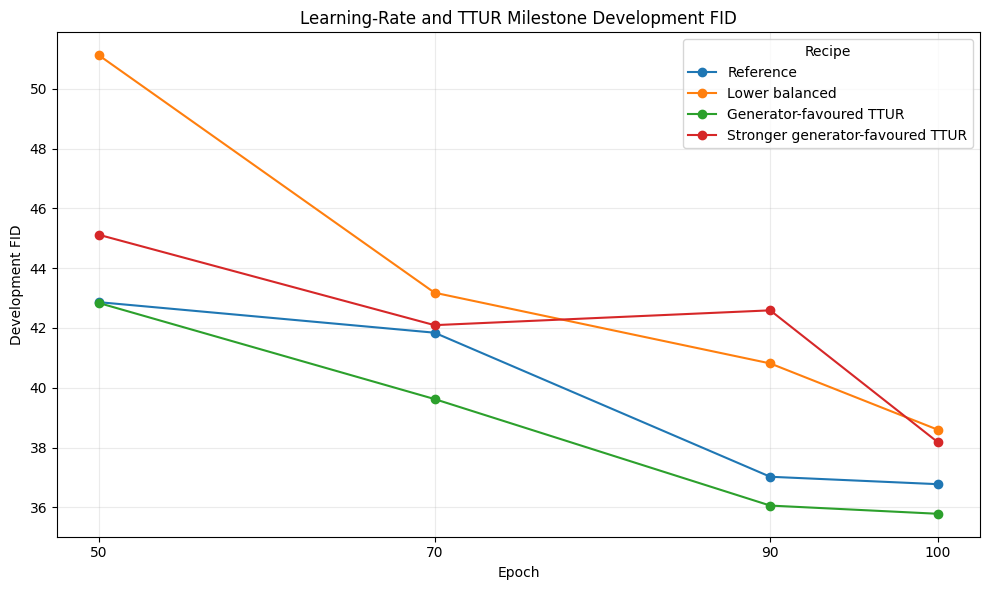

,run_id,recipe,selected_epoch,selected_fid,seed,sample_count
0,G02_dcgan_seed42,Reference,100,36.7759,1001,5000
1,G07_recipe_lowerbalanced_seed42,Lower balanced,100,38.5936,1001,5000
2,G07_recipe_generatorfavoured_seed42,Generator-favoured TTUR,100,35.7858,1001,5000
3,G07_recipe_strongergeneratorfavoured_seed42,Stronger generator-favoured TTUR,100,38.1741,1001,5000


Four follow-up milestone FIDs completed or loaded.
The four-recipe family table and figure were updated.
Checkpoint minima are provisional until the visual and stability evidence is reviewed.
No Tier 2 shortlist decision has been made.
Protected test set remains unused.


In [48]:
required_lr_ttur_followup_fid_objects = [
    "CURRENT_LATENT_DIM",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "MILESTONE_FID_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
]

missing_lr_ttur_followup_fid_objects = [
    name
    for name in required_lr_ttur_followup_fid_objects
    if name not in globals()
]

assert not missing_lr_ttur_followup_fid_objects, (
    "Incomplete follow-up FID setup:\n"
    + "\n".join(
        missing_lr_ttur_followup_fid_objects
    )
)


LR_TTUR_FOLLOWUP_RUN_ID = (
    LR_TTUR_STRONGER_GENERATOR_FAVOURED_RUN_ID
)

LR_TTUR_FOLLOWUP_RECIPE = (
    "Stronger generator-favoured TTUR"
)

LR_TTUR_FOLLOWUP_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_FOLLOWUP_RUN_ID}_"
        "fid_results.csv"
    )
)

LR_TTUR_FAMILY_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / "learning_rate_ttur_milestone_fid.csv"
)

LR_TTUR_FOUR_FID_FIGURE_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_"
        "milestone_fid_four_recipes.png"
    )
)

LR_TTUR_FOUR_SELECTED_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier1_checkpoint_summary_four_recipes.csv"
    )
)


FID_RESULT_COLUMNS = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]


assert CURRENT_LATENT_DIM == 100
assert FID_SAMPLE_COUNT == 5_000
assert MILESTONE_FID_SEED == 1_001

assert real_fid_mean.shape == (
    2_048,
)

assert real_fid_covariance.shape == (
    2_048,
    2_048,
)

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()

assert fid_feature_extractor.trainable is False


if LR_TTUR_FOLLOWUP_FID_PATH.is_file():
    followup_fid_df = pd.read_csv(
        LR_TTUR_FOLLOWUP_FID_PATH
    )

    missing_fid_columns = [
        column
        for column in FID_RESULT_COLUMNS
        if column not in followup_fid_df.columns
    ]

    assert not missing_fid_columns, (
        "Follow-up FID file is missing:\n"
        + "\n".join(
            missing_fid_columns
        )
    )

    followup_fid_df = followup_fid_df[
        FID_RESULT_COLUMNS
    ].copy()

else:
    followup_fid_df = pd.DataFrame(
        columns=FID_RESULT_COLUMNS
    )


keras.backend.clear_session()

followup_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

assert (
    followup_generator.count_params()
    == 1_085_187
)


followup_milestone_rows = []


for epoch in LR_TTUR_MILESTONE_EPOCHS:
    existing_row = followup_fid_df.loc[
        (
            followup_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                followup_fid_df["epoch"],
                errors="coerce",
            )
            == epoch
        )
        & (
            pd.to_numeric(
                followup_fid_df["seed"],
                errors="coerce",
            )
            == MILESTONE_FID_SEED
        )
        & (
            pd.to_numeric(
                followup_fid_df[
                    "sample_count"
                ],
                errors="coerce",
            )
            == FID_SAMPLE_COUNT
        )
    ]


    if len(existing_row) == 1:
        fid_value = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already "
            f"saved: FID {fid_value:.4f}"
        )

    else:
        milestone_weights_path = (
            WEIGHTS_DIR
            / (
                f"{LR_TTUR_FOLLOWUP_RUN_ID}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )

        assert milestone_weights_path.is_file(), (
            "Missing milestone weights:\n"
            f"{milestone_weights_path}"
        )


        followup_generator.load_weights(
            milestone_weights_path
        )


        generated_images = (
            generate_images_uint8(
                generator=followup_generator,
                sample_count=FID_SAMPLE_COUNT,
                latent_dim=CURRENT_LATENT_DIM,
                seed=MILESTONE_FID_SEED,
            )
        )


        generated_features = (
            extract_inception_features(
                images_uint8=generated_images,
                feature_extractor=(
                    fid_feature_extractor
                ),
                batch_size=FID_BATCH_SIZE,
            )
        )


        (
            generated_mean,
            generated_covariance,
        ) = calculate_feature_statistics(
            generated_features
        )


        fid_value = (
            calculate_fid_from_statistics(
                real_fid_mean,
                real_fid_covariance,
                generated_mean,
                generated_covariance,
            )
        )

        assert np.isfinite(
            fid_value
        )


        new_row = pd.DataFrame(
            [
                {
                    "evaluation": "milestone",
                    "epoch": int(epoch),
                    "seed": int(
                        MILESTONE_FID_SEED
                    ),
                    "sample_count": int(
                        FID_SAMPLE_COUNT
                    ),
                    "fid": float(
                        fid_value
                    ),
                }
            ]
        )


        followup_fid_df = followup_fid_df.loc[
            ~(
                (
                    followup_fid_df[
                        "evaluation"
                    ].astype(str)
                    == "milestone"
                )
                & (
                    pd.to_numeric(
                        followup_fid_df["epoch"],
                        errors="coerce",
                    )
                    == epoch
                )
            )
        ]


        followup_fid_df = pd.concat(
            [
                followup_fid_df,
                new_row,
            ],
            ignore_index=True,
        )


        followup_fid_df.to_csv(
            LR_TTUR_FOLLOWUP_FID_PATH,
            index=False,
        )


        print(
            f"Epoch {epoch:03d} "
            f"development FID: "
            f"{fid_value:.4f}"
        )


        del generated_images
        del generated_features
        del generated_mean
        del generated_covariance

        _ = gc.collect()


    followup_milestone_rows.append(
        {
            "run_id": (
                LR_TTUR_FOLLOWUP_RUN_ID
            ),
            "recipe": (
                LR_TTUR_FOLLOWUP_RECIPE
            ),
            "epoch": int(epoch),
            "seed": int(
                MILESTONE_FID_SEED
            ),
            "sample_count": int(
                FID_SAMPLE_COUNT
            ),
            "fid": float(
                fid_value
            ),
        }
    )


del followup_generator

keras.backend.clear_session()
_ = gc.collect()


followup_family_rows_df = (
    pd.DataFrame(
        followup_milestone_rows
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)

assert len(
    followup_family_rows_df
) == 4


assert (
    LR_TTUR_FAMILY_MILESTONE_FID_PATH
    .is_file()
), (
    "Existing three-recipe family FID file "
    "was not found:\n"
    f"{LR_TTUR_FAMILY_MILESTONE_FID_PATH}"
)


existing_family_fid_df = pd.read_csv(
    LR_TTUR_FAMILY_MILESTONE_FID_PATH
)

required_family_columns = [
    "run_id",
    "recipe",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]

missing_family_columns = [
    column
    for column in required_family_columns
    if column not in existing_family_fid_df.columns
]

assert not missing_family_columns, (
    "Existing family FID file is missing:\n"
    + "\n".join(
        missing_family_columns
    )
)


existing_family_fid_df = (
    existing_family_fid_df.loc[
        existing_family_fid_df[
            "run_id"
        ]
        != LR_TTUR_FOLLOWUP_RUN_ID
    ]
    .copy()
)


lr_ttur_four_family_fid_df = (
    pd.concat(
        [
            existing_family_fid_df[
                required_family_columns
            ],
            followup_family_rows_df[
                required_family_columns
            ],
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "recipe",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    lr_ttur_four_family_fid_df
) == 16

assert np.isfinite(
    lr_ttur_four_family_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


lr_ttur_four_family_fid_df.to_csv(
    LR_TTUR_FAMILY_MILESTONE_FID_PATH,
    index=False,
)


recipe_order = [
    "Reference",
    "Lower balanced",
    "Generator-favoured TTUR",
    "Stronger generator-favoured TTUR",
]


lr_ttur_four_fid_table = (
    lr_ttur_four_family_fid_df
    .pivot(
        index="recipe",
        columns="epoch",
        values="fid",
    )
    .reindex(
        recipe_order
    )
    .rename_axis(
        index="Recipe",
        columns="Epoch",
    )
)


display(
    lr_ttur_four_fid_table.round(4)
)


plt.figure(
    figsize=(10, 6)
)

for recipe in recipe_order:
    recipe_df = (
        lr_ttur_four_family_fid_df.loc[
            lr_ttur_four_family_fid_df[
                "recipe"
            ] == recipe
        ]
        .sort_values("epoch")
    )

    plt.plot(
        recipe_df["epoch"],
        recipe_df["fid"],
        marker="o",
        label=recipe,
    )


plt.title(
    (
        "Learning-Rate and TTUR "
        "Milestone Development FID"
    )
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Development FID"
)

plt.xticks(
    LR_TTUR_MILESTONE_EPOCHS
)

plt.grid(
    alpha=0.25
)

plt.legend(
    title="Recipe"
)

plt.tight_layout()

plt.savefig(
    LR_TTUR_FOUR_FID_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


selected_row_indices = (
    lr_ttur_four_family_fid_df
    .groupby("recipe")["fid"]
    .idxmin()
)

lr_ttur_four_selected_checkpoint_df = (
    lr_ttur_four_family_fid_df.loc[
        selected_row_indices
    ]
    .copy()
    .rename(
        columns={
            "epoch": "selected_epoch",
            "fid": "selected_fid",
        }
    )
    .set_index("recipe")
    .reindex(recipe_order)
    .reset_index()
)


lr_ttur_four_selected_checkpoint_df.to_csv(
    LR_TTUR_FOUR_SELECTED_SUMMARY_PATH,
    index=False,
)


display(
    lr_ttur_four_selected_checkpoint_df[
        [
            "run_id",
            "recipe",
            "selected_epoch",
            "selected_fid",
            "seed",
            "sample_count",
        ]
    ].round(4)
)


print(
    "Four follow-up milestone FIDs "
    "completed or loaded."
)

print(
    "The four-recipe family table and "
    "figure were updated."
)

print(
    "Checkpoint minima are provisional "
    "until the visual and stability "
    "evidence is reviewed."
)

print(
    "No Tier 2 shortlist decision has "
    "been made."
)

print(
    "Protected test set remains unused."
)

### 10.6 Tier 1 Learning-Rate and TTUR Decision

All four learning-rate and TTUR recipes completed the same 100-epoch training budget, used identical model architecture and update exposure, and were evaluated using the same fixed-seed progression and development-FID protocol.

All four recipes achieved their lowest measured milestone FID at epoch 100.

The lower-balanced recipe produced an epoch-100 FID of `38.5936`, which was `1.8177` worse than the reference. It also provided no clear visual, stability or compute advantage and therefore stops after Tier 1.

The original generator-favoured TTUR recipe produced the strongest Tier 1 result, with an epoch-100 FID of `35.7858`. This was `0.9901` better than the reference FID of `36.7759`.

The stronger generator-favoured recipe substantially reduced discriminator strength. Its late score separation fell to `0.7359`, compared with `0.8539` for the original generator-favoured recipe. However, this did not improve generated-image quality: its epoch-100 FID was `38.1741`, which was `1.3982` worse than the reference and `2.3883` worse than the original generator-favoured recipe.

The stronger recipe did not exhibit obvious mode collapse, but weakening the discriminator further did not produce a useful quality advantage. It therefore stops after Tier 1.

The reference and original generator-favoured TTUR recipe advance to Tier 2. Because their FID difference is below the locked `2.0` practical margin, the result is treated as a practical tie rather than an adopted improvement.

No further learning-rate, TTUR or update-ratio recipe will be trained.

In [50]:
LR_TTUR_PRACTICAL_FID_MARGIN = 2.0

LR_TTUR_TIER2_REFERENCE_RUN_ID = (
    LR_TTUR_REFERENCE_RUN_ID
)

LR_TTUR_TIER2_CANDIDATE_RUN_ID = (
    LR_TTUR_GENERATOR_FAVOURED_RUN_ID
)

LR_TTUR_TIER2_REFERENCE_EPOCH = 100
LR_TTUR_TIER2_CANDIDATE_EPOCH = 100


lr_ttur_tier1_summary_df = (
    lr_ttur_four_selected_checkpoint_df.copy()
)

reference_selected_fid = float(
    lr_ttur_tier1_summary_df.loc[
        lr_ttur_tier1_summary_df[
            "recipe"
        ] == "Reference",
        "selected_fid",
    ].iloc[0]
)

lr_ttur_tier1_summary_df[
    "fid_difference_vs_reference"
] = (
    lr_ttur_tier1_summary_df[
        "selected_fid"
    ]
    - reference_selected_fid
)

lr_ttur_tier1_summary_df[
    "tier_outcome"
] = (
    lr_ttur_tier1_summary_df[
        "recipe"
    ].map(
        {
            "Reference": "Tier 2 reference",
            "Lower balanced": "Stop after Tier 1",
            "Generator-favoured TTUR": (
                "Tier 2 candidate"
            ),
            "Stronger generator-favoured TTUR": (
                "Stop after Tier 1"
            ),
        }
    )
)


LR_TTUR_TIER2_REFERENCE_FID = float(
    lr_ttur_tier1_summary_df.loc[
        lr_ttur_tier1_summary_df[
            "recipe"
        ] == "Reference",
        "selected_fid",
    ].iloc[0]
)

LR_TTUR_TIER2_CANDIDATE_FID = float(
    lr_ttur_tier1_summary_df.loc[
        lr_ttur_tier1_summary_df[
            "recipe"
        ] == "Generator-favoured TTUR",
        "selected_fid",
    ].iloc[0]
)

LR_TTUR_SCREENING_FID_IMPROVEMENT = (
    LR_TTUR_TIER2_REFERENCE_FID
    - LR_TTUR_TIER2_CANDIDATE_FID
)


assert (
    lr_ttur_tier1_summary_df[
        "selected_epoch"
    ].astype(int).tolist()
    == [100, 100, 100, 100]
)

assert np.isclose(
    LR_TTUR_SCREENING_FID_IMPROVEMENT,
    0.9901,
    atol=1e-4,
)

assert (
    LR_TTUR_SCREENING_FID_IMPROVEMENT
    < LR_TTUR_PRACTICAL_FID_MARGIN
)


LR_TTUR_TIER1_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier1_final_summary.csv"
    )
)

lr_ttur_tier1_summary_df.to_csv(
    LR_TTUR_TIER1_SUMMARY_PATH,
    index=False,
)


display(
    lr_ttur_tier1_summary_df[
        [
            "run_id",
            "recipe",
            "selected_epoch",
            "selected_fid",
            "fid_difference_vs_reference",
            "tier_outcome",
        ]
    ].round(4)
)


print(
    "Tier 2 reference:",
    LR_TTUR_TIER2_REFERENCE_RUN_ID,
    "epoch",
    LR_TTUR_TIER2_REFERENCE_EPOCH,
)

print(
    "Tier 2 candidate:",
    LR_TTUR_TIER2_CANDIDATE_RUN_ID,
    "epoch",
    LR_TTUR_TIER2_CANDIDATE_EPOCH,
)

print(
    "Seed-42 screening improvement:",
    f"{LR_TTUR_SCREENING_FID_IMPROVEMENT:.4f}",
)

print(
    "Practical FID margin:",
    f"{LR_TTUR_PRACTICAL_FID_MARGIN:.4f}",
)

print(
    "Lower-balanced and stronger "
    "generator-favoured recipes stop "
    "after Tier 1."
)

print(
    "No recipe has been adopted."
)

print(
    "Saved:",
    LR_TTUR_TIER1_SUMMARY_PATH,
)

,run_id,recipe,selected_epoch,selected_fid,fid_difference_vs_reference,tier_outcome
0,G02_dcgan_seed42,Reference,100,36.7759,0.0000,Tier 2 reference
1,G07_recipe_lowerbalanced_seed42,Lower balanced,100,38.5936,1.8177,Stop after Tier 1
2,G07_recipe_generatorfavoured_seed42,Generator-favoured TTUR,100,35.7858,-0.9902,Tier 2 candidate
3,G07_recipe_strongergeneratorfavoured_seed42,Stronger generator-favoured TTUR,100,38.1741,1.3982,Stop after Tier 1


Tier 2 reference: G02_dcgan_seed42 epoch 100
Tier 2 candidate: G07_recipe_generatorfavoured_seed42 epoch 100
Seed-42 screening improvement: 0.9902
Practical FID margin: 2.0000
Lower-balanced and stronger generator-favoured recipes stop after Tier 1.
No recipe has been adopted.
Saved: [local project directory]/histories/learning_rate_ttur_tier1_final_summary.csv


### 10.7 Tier 2 Repeated Development FID

Tier 1 shortlisted the reference and the original generator-favoured TTUR recipe at epoch 100.

Their one-draw milestone FID difference was only `0.9901`, below the locked `2.0` practical margin. Three independent 5,000-image FID estimates are therefore calculated at each selected checkpoint using seeds `1002`, `1003` and `1004`.

The reference results are reused from the completed baseline calibration. Only the candidate repeated FIDs are newly computed.

Repeated FID measures variation caused by generated sampling from one fixed checkpoint. It does not measure variation between independent training runs.

No official CIFAR-10 test image is used.

In [51]:
required_lr_ttur_repeat_objects = [
    "REPEATED_FID_SEEDS",
    "FID_SAMPLE_COUNT",
    "FID_FEATURE_DIM",
    "FID_BATCH_SIZE",
    "CURRENT_LATENT_DIM",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_lr_ttur_repeat_objects = [
    name
    for name in required_lr_ttur_repeat_objects
    if name not in globals()
]

assert not missing_lr_ttur_repeat_objects, (
    "Incomplete repeated-FID setup:\n"
    + "\n".join(
        missing_lr_ttur_repeat_objects
    )
)


LR_TTUR_TIER2_REPEAT_SEEDS = tuple(
    REPEATED_FID_SEEDS
)

assert LR_TTUR_TIER2_REPEAT_SEEDS == (
    1002,
    1003,
    1004,
)


lr_ttur_candidate_weights_path = (
    WEIGHTS_DIR
    / (
        f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{LR_TTUR_TIER2_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

assert lr_ttur_candidate_weights_path.is_file(), (
    "Missing candidate generator weights:\n"
    f"{lr_ttur_candidate_weights_path}"
)


# Reuse the established reference repeats.
lr_ttur_reference_repeat_path = (
    HISTORIES_DIR
    / "baseline_calibration_corrected_repeated_fid.csv"
)

assert lr_ttur_reference_repeat_path.is_file(), (
    "Missing reference repeated-FID file:\n"
    f"{lr_ttur_reference_repeat_path}"
)

lr_ttur_reference_repeat_all_df = pd.read_csv(
    lr_ttur_reference_repeat_path
)

lr_ttur_reference_repeat_df = (
    lr_ttur_reference_repeat_all_df.loc[
        (
            lr_ttur_reference_repeat_all_df[
                "run_id"
            ]
            == LR_TTUR_TIER2_REFERENCE_RUN_ID
        )
        & (
            lr_ttur_reference_repeat_all_df[
                "repeat_seed"
            ]
            .astype(int)
            .isin(
                LR_TTUR_TIER2_REPEAT_SEEDS
            )
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

assert len(
    lr_ttur_reference_repeat_df
) == 3


lr_ttur_candidate_repeat_path = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "generatorfavoured_seed42_"
        "repeated_fid.csv"
    )
)

candidate_repeat_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]


if lr_ttur_candidate_repeat_path.is_file():
    lr_ttur_candidate_repeat_df = pd.read_csv(
        lr_ttur_candidate_repeat_path
    )
else:
    lr_ttur_candidate_repeat_df = pd.DataFrame(
        columns=candidate_repeat_columns
    )


tf.keras.backend.clear_session()

lr_ttur_candidate_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_candidate_generator.load_weights(
    lr_ttur_candidate_weights_path
)

assert (
    lr_ttur_candidate_generator.count_params()
    == 1_085_187
)


for repeat_seed in LR_TTUR_TIER2_REPEAT_SEEDS:
    existing_row = (
        lr_ttur_candidate_repeat_df.loc[
            pd.to_numeric(
                lr_ttur_candidate_repeat_df.get(
                    "repeat_seed",
                    pd.Series(dtype=int),
                ),
                errors="coerce",
            )
            == repeat_seed
        ]
    )

    if len(existing_row) == 1:
        existing_fid = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Repeat seed {repeat_seed} "
            f"already saved: "
            f"FID {existing_fid:.4f}"
        )

        continue


    generated_images = generate_images_uint8(
        generator=lr_ttur_candidate_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=int(repeat_seed),
    )

    assert generated_images.shape == (
        FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8


    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    assert generated_features.shape == (
        FID_SAMPLE_COUNT,
        FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    fid_value = (
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            generated_mean,
            generated_covariance,
        )
    )

    assert np.isfinite(
        fid_value
    )


    new_row = pd.DataFrame(
        [
            {
                "run_id": (
                    LR_TTUR_TIER2_CANDIDATE_RUN_ID
                ),
                "training_seed": 42,
                "selected_epoch": (
                    LR_TTUR_TIER2_CANDIDATE_EPOCH
                ),
                "repeat_seed": int(
                    repeat_seed
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        ]
    )


    lr_ttur_candidate_repeat_df = pd.concat(
        [
            lr_ttur_candidate_repeat_df,
            new_row,
        ],
        ignore_index=True,
    )

    lr_ttur_candidate_repeat_df = (
        lr_ttur_candidate_repeat_df
        .drop_duplicates(
            subset=[
                "run_id",
                "repeat_seed",
            ],
            keep="last",
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )

    lr_ttur_candidate_repeat_df.to_csv(
        lr_ttur_candidate_repeat_path,
        index=False,
    )


    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    _ = gc.collect()


del lr_ttur_candidate_generator

tf.keras.backend.clear_session()
_ = gc.collect()


lr_ttur_candidate_repeat_df = (
    lr_ttur_candidate_repeat_df.loc[
        lr_ttur_candidate_repeat_df[
            "repeat_seed"
        ]
        .astype(int)
        .isin(
            LR_TTUR_TIER2_REPEAT_SEEDS
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)

assert len(
    lr_ttur_candidate_repeat_df
) == 3


lr_ttur_reference_repeat_mean = float(
    lr_ttur_reference_repeat_df[
        "fid"
    ].mean()
)

lr_ttur_reference_repeat_sd = float(
    lr_ttur_reference_repeat_df[
        "fid"
    ].std(ddof=1)
)

lr_ttur_candidate_repeat_mean = float(
    lr_ttur_candidate_repeat_df[
        "fid"
    ].mean()
)

lr_ttur_candidate_repeat_sd = float(
    lr_ttur_candidate_repeat_df[
        "fid"
    ].std(ddof=1)
)

lr_ttur_repeated_fid_improvement = (
    lr_ttur_reference_repeat_mean
    - lr_ttur_candidate_repeat_mean
)


lr_ttur_repeated_fid_summary_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference",
            "Run ID": (
                LR_TTUR_TIER2_REFERENCE_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_TIER2_REFERENCE_EPOCH
            ),
            "Repeated FID mean": (
                lr_ttur_reference_repeat_mean
            ),
            "Repeated FID SD": (
                lr_ttur_reference_repeat_sd
            ),
        },
        {
            "Configuration": (
                "Generator-favoured TTUR"
            ),
            "Run ID": (
                LR_TTUR_TIER2_CANDIDATE_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_TIER2_CANDIDATE_EPOCH
            ),
            "Repeated FID mean": (
                lr_ttur_candidate_repeat_mean
            ),
            "Repeated FID SD": (
                lr_ttur_candidate_repeat_sd
            ),
        },
    ]
)


lr_ttur_repeated_fid_summary_path = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_repeated_fid_summary.csv"
    )
)

lr_ttur_repeated_fid_summary_df.to_csv(
    lr_ttur_repeated_fid_summary_path,
    index=False,
)


display(
    lr_ttur_reference_repeat_df.round(4)
)

display(
    lr_ttur_candidate_repeat_df.round(4)
)

display(
    lr_ttur_repeated_fid_summary_df.round(4)
)


print(
    "Repeated-FID improvement favouring "
    "generator-favoured TTUR:",
    f"{lr_ttur_repeated_fid_improvement:.4f}",
)

if (
    lr_ttur_repeated_fid_improvement
    > LR_TTUR_PRACTICAL_FID_MARGIN
):
    print(
        "Candidate clears the practical "
        "FID margin."
    )

elif (
    lr_ttur_repeated_fid_improvement
    >= -LR_TTUR_PRACTICAL_FID_MARGIN
):
    print(
        "Repeated FID remains a "
        "practical tie."
    )

else:
    print(
        "Candidate is meaningfully worse "
        "under repeated FID."
    )

print(
    "The complete Tier 2 safeguard package "
    "still follows for the two shortlisted "
    "configurations."
)

print(
    "No seed-123 confirmation has "
    "been triggered."
)

print(
    "Saved:",
    lr_ttur_repeated_fid_summary_path,
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_965/2089426386.py:260: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lr_ttur_candidate_repeat_df = pd.concat(


Repeat seed 1002: FID 35.8661


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 35.3226


...

Repeat seed 1004: FID 36.0990


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G02_dcgan_seed42,42,100,1002,5000,36.9692
1,G02_dcgan_seed42,42,100,1003,5000,37.3644
2,G02_dcgan_seed42,42,100,1004,5000,36.7445


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G07_recipe_generatorfavoured_seed42,42,100,1002,5000,35.8661
1,G07_recipe_generatorfavoured_seed42,42,100,1003,5000,35.3226
2,G07_recipe_generatorfavoured_seed42,42,100,1004,5000,36.0990


,Configuration,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD
0,Reference,G02_dcgan_seed42,100,37.0260,0.3139
1,Generator-favoured TTUR,G07_recipe_generatorfavoured_seed42,100,35.7626,0.3984


Repeated-FID improvement favouring generator-favoured TTUR: 1.2635
Repeated FID remains a practical tie.
The complete Tier 2 safeguard package still follows for the two shortlisted configurations.
No seed-123 confirmation has been triggered.
Saved: [local project directory]/histories/learning_rate_ttur_tier2_repeated_fid_summary.csv


#### Repeated-FID Finding

The generator-favoured TTUR checkpoint produced a lower FID than the reference under all three repeated sampling seeds.

| Repeat seed | Reference FID | Generator-favoured TTUR FID | Candidate improvement |
|---:|---:|---:|---:|
| `1002` | `36.9692` | `35.8661` | `1.1031` |
| `1003` | `37.3644` | `35.3226` | `2.0418` |
| `1004` | `36.7445` | `36.0990` | `0.6455` |

The repeated mean FID improved from `37.0260` to `35.7626`, an improvement of `1.2635`.

This confirms that the candidate's favourable Tier 1 result was not caused by one unusually favourable generated sample. However, the improvement remains below the locked `2.0` practical FID margin and is therefore treated as a practical tie.

The candidate also showed slightly greater sampling variation, with an FID standard deviation of `0.3984` compared with `0.3139` for the reference. Both values remain small relative to the overall FID scale, so this difference is supporting evidence rather than a stability concern.

No recipe is adopted from repeated FID alone. The comparison proceeds to the complete Tier 2 safeguard package. Seed-123 confirmation remains deferred until the candidate earns provisional adoption.

### 10.8 Selected-Checkpoint Visual and Manual Quality Evidence

The reference and generator-favoured TTUR recipe are compared at their selected epoch-100 checkpoints.

Two visual sets are used for each model:

- the fixed-seed grid retained from training;
- a new uncurated grid generated from the shared uncurated seed.

The fixed grid supports direct comparison with training progression. The uncurated grid checks whether the observed quality extends to a fresh latent sample rather than only the familiar monitoring inputs.

The generator-favoured candidate additionally generates 100 uncurated numbered images using the shared manual-evaluation seed.

Each image is classified as:

- **Clear:** recognisable object with plausible overall structure;
- **Marginal:** object-like or class-related features are present, but the image remains blurry, distorted, incomplete or uncertain;
- **Nonsense:** no coherent object structure or meaningful class-related cues.

A recognised CIFAR-10 class or `Unclear` is also recorded for each image.

The existing reference manual result is reused because it was produced using the same model checkpoint, seed, grid construction and scoring definitions:

- Clear: `9`;
- Marginal: `75`;
- Nonsense: `16`.

Manual differences below approximately 13 images out of 100 are treated as inconclusive on their own.

In [54]:
required_lr_ttur_visual_objects = [
    "LR_TTUR_TIER2_REFERENCE_RUN_ID",
    "LR_TTUR_TIER2_CANDIDATE_RUN_ID",
    "LR_TTUR_TIER2_REFERENCE_EPOCH",
    "LR_TTUR_TIER2_CANDIDATE_EPOCH",
    "CURRENT_LATENT_DIM",
    "UNCURATED_GRID_SEED",
    "MANUAL_EVALUATION_SEED",
    "WEIGHTS_DIR",
    "GRIDS_DIR",
    "build_dcgan_generator",
    "make_stateless_noise",
    "save_generated_grid",
    "generate_images_uint8",
    "save_numbered_manual_grid",
]

missing_lr_ttur_visual_objects = [
    name
    for name in required_lr_ttur_visual_objects
    if name not in globals()
]

assert not missing_lr_ttur_visual_objects, (
    "Incomplete selected-checkpoint visual setup:\n"
    + "\n".join(
        missing_lr_ttur_visual_objects
    )
)


LR_TTUR_REFERENCE_WEIGHTS_PATH = (
    WEIGHTS_DIR
    / (
        f"{LR_TTUR_TIER2_REFERENCE_RUN_ID}_"
        f"epoch{LR_TTUR_TIER2_REFERENCE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

LR_TTUR_CANDIDATE_WEIGHTS_PATH = (
    WEIGHTS_DIR
    / (
        f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{LR_TTUR_TIER2_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

assert LR_TTUR_REFERENCE_WEIGHTS_PATH.is_file()
assert LR_TTUR_CANDIDATE_WEIGHTS_PATH.is_file()


tf.keras.backend.clear_session()

lr_ttur_reference_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_candidate_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_reference_generator.load_weights(
    LR_TTUR_REFERENCE_WEIGHTS_PATH
)

lr_ttur_candidate_generator.load_weights(
    LR_TTUR_CANDIDATE_WEIGHTS_PATH
)


assert (
    lr_ttur_reference_generator.count_params()
    == 1_085_187
)

assert (
    lr_ttur_candidate_generator.count_params()
    == 1_085_187
)

print(
    "Reference and generator-favoured "
    "epoch-100 checkpoints loaded."
)

Reference and generator-favoured epoch-100 checkpoints loaded.


In [55]:
LR_TTUR_REFERENCE_FIXED_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_TIER2_REFERENCE_RUN_ID}_"
        f"epoch{LR_TTUR_TIER2_REFERENCE_EPOCH:03d}.png"
    )
)

LR_TTUR_CANDIDATE_FIXED_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{LR_TTUR_TIER2_CANDIDATE_EPOCH:03d}.png"
    )
)

LR_TTUR_REFERENCE_UNCURATED_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_TIER2_REFERENCE_RUN_ID}_"
        "tier2_uncurated.png"
    )
)

LR_TTUR_CANDIDATE_UNCURATED_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}_"
        "tier2_uncurated.png"
    )
)

LR_TTUR_SELECTED_VISUAL_COMPARISON_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_"
        "tier2_selected_visual_comparison.png"
    )
)


assert LR_TTUR_REFERENCE_FIXED_GRID_PATH.is_file()
assert LR_TTUR_CANDIDATE_FIXED_GRID_PATH.is_file()


lr_ttur_uncurated_noise = (
    make_stateless_noise(
        sample_count=25,
        latent_dim=CURRENT_LATENT_DIM,
        seed=UNCURATED_GRID_SEED,
    )
)

assert lr_ttur_uncurated_noise.shape == (
    25,
    CURRENT_LATENT_DIM,
)


save_generated_grid(
    generator=lr_ttur_reference_generator,
    noise=lr_ttur_uncurated_noise,
    save_path=(
        LR_TTUR_REFERENCE_UNCURATED_GRID_PATH
    ),
    title=(
        "Reference DCGAN, Epoch 100, "
        "Uncurated Grid"
    ),
)

save_generated_grid(
    generator=lr_ttur_candidate_generator,
    noise=lr_ttur_uncurated_noise,
    save_path=(
        LR_TTUR_CANDIDATE_UNCURATED_GRID_PATH
    ),
    title=(
        "Generator-Favoured TTUR, "
        "Epoch 100, Uncurated Grid"
    ),
)


assert (
    LR_TTUR_REFERENCE_UNCURATED_GRID_PATH
    .is_file()
)

assert (
    LR_TTUR_CANDIDATE_UNCURATED_GRID_PATH
    .is_file()
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14),
)

comparison_images = [
    (
        LR_TTUR_REFERENCE_FIXED_GRID_PATH,
        "Reference: fixed-seed grid",
    ),
    (
        LR_TTUR_CANDIDATE_FIXED_GRID_PATH,
        "Generator-favoured TTUR: "
        "fixed-seed grid",
    ),
    (
        LR_TTUR_REFERENCE_UNCURATED_GRID_PATH,
        "Reference: uncurated grid",
    ),
    (
        LR_TTUR_CANDIDATE_UNCURATED_GRID_PATH,
        "Generator-favoured TTUR: "
        "uncurated grid",
    ),
]

for axis, (
    image_path,
    image_title,
) in zip(
    axes.flat,
    comparison_images,
):
    axis.imshow(
        plt.imread(image_path)
    )

    axis.set_title(
        image_title,
        fontsize=11,
    )

    axis.axis("off")


fig.suptitle(
    (
        "Learning-Rate and TTUR "
        "Selected-Checkpoint Visual Comparison"
    ),
    fontsize=15,
    y=0.995,
)

plt.tight_layout(
    rect=(0, 0, 1, 0.97)
)

fig.savefig(
    LR_TTUR_SELECTED_VISUAL_COMPARISON_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "Selected-checkpoint visual "
    "comparison saved:"
)

print(
    LR_TTUR_SELECTED_VISUAL_COMPARISON_PATH
)

Selected-checkpoint visual comparison saved:
[local project directory]/grids/learning_rate_ttur_tier2_selected_visual_comparison.png


In [56]:
LR_TTUR_CANDIDATE_MANUAL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}_"
        "tier2_manual_100.png"
    )
)


lr_ttur_candidate_manual_images = (
    generate_images_uint8(
        generator=lr_ttur_candidate_generator,
        sample_count=100,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MANUAL_EVALUATION_SEED,
    )
)

assert lr_ttur_candidate_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert (
    lr_ttur_candidate_manual_images.dtype
    == np.uint8
)


save_numbered_manual_grid(
    images_uint8=(
        lr_ttur_candidate_manual_images
    ),
    output_path=(
        LR_TTUR_CANDIDATE_MANUAL_GRID_PATH
    ),
    title=(
        "Generator-Favoured TTUR, "
        "Epoch 100, Manual Scoring Images"
    ),
)


print(
    "Candidate manual-scoring grid saved:"
)

print(
    LR_TTUR_CANDIDATE_MANUAL_GRID_PATH
)

print(
    "Score all 100 images as Clear, "
    "Marginal or Nonsense."
)

print(
    "Also record a recognised CIFAR-10 "
    "class or Unclear for each image."
)

print(
    "Reference manual result reused: "
    "9 Clear, 75 Marginal, 16 Nonsense."
)

Candidate manual-scoring grid saved:
[local project directory]/grids/G07_recipe_generatorfavoured_seed42_tier2_manual_100.png
Score all 100 images as Clear, Marginal or Nonsense.
Also record a recognised CIFAR-10 class or Unclear for each image.
Reference manual result reused: 9 Clear, 75 Marginal, 16 Nonsense.


#### Manual Quality Scoring Result

The generator-favoured TTUR checkpoint was evaluated using the same strict 100-image Clear, Marginal and Nonsense criteria previously applied to the reference DCGAN.

| Quality category | Reference DCGAN | Generator-favoured TTUR | Candidate minus reference |
|---|---:|---:|---:|
| Clear | 9 | 17 | +8 |
| Marginal | 75 | 71 | −4 |
| Nonsense | 16 | 12 | −4 |

The candidate produced more immediately recognisable images and fewer outputs without coherent object structure. However, many outputs containing identifiable class cues remained blurry, structurally distorted or ambiguous and were conservatively scored as Marginal rather than Clear.

The Clear count increased by eight images. This is below the approximate 13-image resolution threshold used for the 100-image manual assessment. The reduction from 16 to 12 Nonsense images also supports the candidate, but neither difference is large enough to establish superiority independently.

Manual scoring therefore provides supportive but inconclusive evidence for the generator-favoured TTUR recipe. The result must be interpreted alongside repeated FID, classifier-supported coverage, descriptor similarity, feature-space diversity and repetition evidence.

Manual evaluation remains subjective and was not blinded because the model identities were visible during review.

In [61]:
LR_TTUR_REFERENCE_MANUAL_COUNTS = {
    "Clear": 9,
    "Marginal": 75,
    "Nonsense": 16,
}

LR_TTUR_CANDIDATE_MANUAL_COUNTS = {
    "Clear": 17,
    "Marginal": 71,
    "Nonsense": 12,
}

LR_TTUR_MANUAL_RESOLUTION = 13


assert sum(
    LR_TTUR_REFERENCE_MANUAL_COUNTS.values()
) == 100

assert sum(
    LR_TTUR_CANDIDATE_MANUAL_COUNTS.values()
) == 100


lr_ttur_manual_comparison_df = pd.DataFrame(
    {
        "Reference DCGAN": (
            LR_TTUR_REFERENCE_MANUAL_COUNTS
        ),
        "Generator-favoured TTUR": (
            LR_TTUR_CANDIDATE_MANUAL_COUNTS
        ),
    }
).reindex(
    [
        "Clear",
        "Marginal",
        "Nonsense",
    ]
)

lr_ttur_manual_comparison_df[
    "Candidate minus reference"
] = (
    lr_ttur_manual_comparison_df[
        "Generator-favoured TTUR"
    ]
    - lr_ttur_manual_comparison_df[
        "Reference DCGAN"
    ]
)


candidate_clear_difference = int(
    lr_ttur_manual_comparison_df.loc[
        "Clear",
        "Candidate minus reference",
    ]
)

candidate_nonsense_difference = int(
    lr_ttur_manual_comparison_df.loc[
        "Nonsense",
        "Candidate minus reference",
    ]
)


if (
    candidate_clear_difference
    >= LR_TTUR_MANUAL_RESOLUTION
    and candidate_nonsense_difference <= 0
):
    lr_ttur_manual_interpretation = (
        "Potentially meaningful candidate "
        "quality advantage"
    )

elif (
    candidate_clear_difference > 0
    and candidate_nonsense_difference < 0
):
    lr_ttur_manual_interpretation = (
        "Supportive but inconclusive "
        "candidate advantage"
    )

else:
    lr_ttur_manual_interpretation = (
        "No clear candidate advantage"
    )


LR_TTUR_MANUAL_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_manual_comparison.csv"
    )
)

lr_ttur_manual_comparison_df.to_csv(
    LR_TTUR_MANUAL_COMPARISON_PATH
)


display(
    lr_ttur_manual_comparison_df
)


print(
    "Candidate manual result:",
    "17 Clear, 71 Marginal, 12 Nonsense."
)

print(
    "Clear-count difference versus reference:",
    candidate_clear_difference,
)

print(
    "Nonsense-count difference versus reference:",
    candidate_nonsense_difference,
)

print(
    "Manual comparison resolution:",
    LR_TTUR_MANUAL_RESOLUTION,
    "images out of 100.",
)

print(
    "Interpretation:",
    lr_ttur_manual_interpretation,
)

print(
    "Manual comparison saved:"
)

print(
    LR_TTUR_MANUAL_COMPARISON_PATH
)

print(
    "Protected test set remains unused."
)

,Reference DCGAN,Generator-favoured TTUR,Candidate minus reference
Clear,9,17,8
Marginal,75,71,-4
Nonsense,16,12,-4


Candidate manual result: 17 Clear, 71 Marginal, 12 Nonsense.
Clear-count difference versus reference: 8
Nonsense-count difference versus reference: -4
Manual comparison resolution: 13 images out of 100.
Interpretation: Supportive but inconclusive candidate advantage
Manual comparison saved:
[local project directory]/histories/learning_rate_ttur_tier2_manual_comparison.csv
Protected test set remains unused.


### 10.9 Classifier-Supported Class Coverage

The reference and generator-favoured TTUR checkpoints are evaluated using the frozen CIFAR-10 coverage classifier.

Both generators produce 5,000 images using the same latent seed. This provides a paired comparison in which the model configuration is the only intentional difference.

The primary coverage metric is Jensen-Shannon divergence between:

- the classifier prediction distribution on generated images;
- the classifier prediction distribution on held-out real validation images.

Lower Jensen-Shannon divergence indicates that the generated prediction distribution is closer to the real validation prediction distribution.

The following supporting metrics are also reported:

- number of represented classes;
- dominant-class share;
- normalised class entropy;
- predicted proportion for each CIFAR-10 class.

The classifier is not treated as ground truth. These results measure classifier-supported semantic coverage and must be interpreted alongside manual quality, FID, diversity and visual evidence.

The generated image pools are retained for the subsequent descriptor and diversity analyses, avoiding unnecessary regeneration.

No official CIFAR-10 test image is used.

In [69]:
required_lr_ttur_coverage_objects = [
    "lr_ttur_reference_generator",
    "lr_ttur_candidate_generator",
    "CURRENT_LATENT_DIM",
    "GENERATED_DIVERSITY_SEED",
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "REAL_CLASSIFIER_PREDICTED_PROPORTIONS",
    "generate_images_uint8",
    "summarise_classifier_coverage",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_coverage_objects = [
    name
    for name in required_lr_ttur_coverage_objects
    if name not in globals()
]

assert not missing_lr_ttur_coverage_objects, (
    "Incomplete classifier-coverage setup:\n"
    + "\n".join(
        missing_lr_ttur_coverage_objects
    )
)


LR_TTUR_COVERAGE_SAMPLE_COUNT = 5_000
LR_TTUR_COVERAGE_SEED = GENERATED_DIVERSITY_SEED
LR_TTUR_COVERAGE_BATCH_SIZE = 256

assert LR_TTUR_COVERAGE_SEED == 1302

assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False

assert np.isclose(
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS.sum(),
    1.0,
)


# Use the same latent seed and sample count
# for both selected checkpoints.
lr_ttur_reference_evaluation_images = (
    generate_images_uint8(
        generator=lr_ttur_reference_generator,
        sample_count=LR_TTUR_COVERAGE_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=LR_TTUR_COVERAGE_SEED,
        batch_size=LR_TTUR_COVERAGE_BATCH_SIZE,
    )
)

lr_ttur_candidate_evaluation_images = (
    generate_images_uint8(
        generator=lr_ttur_candidate_generator,
        sample_count=LR_TTUR_COVERAGE_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=LR_TTUR_COVERAGE_SEED,
        batch_size=LR_TTUR_COVERAGE_BATCH_SIZE,
    )
)


assert lr_ttur_reference_evaluation_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert lr_ttur_candidate_evaluation_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert (
    lr_ttur_reference_evaluation_images.dtype
    == np.uint8
)

assert (
    lr_ttur_candidate_evaluation_images.dtype
    == np.uint8
)


(
    lr_ttur_reference_distribution_df,
    lr_ttur_reference_coverage_df,
    lr_ttur_reference_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        lr_ttur_reference_evaluation_images
    ),
    model_label="Reference DCGAN",
    batch_size=LR_TTUR_COVERAGE_BATCH_SIZE,
)

(
    lr_ttur_candidate_distribution_df,
    lr_ttur_candidate_coverage_df,
    lr_ttur_candidate_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        lr_ttur_candidate_evaluation_images
    ),
    model_label="Generator-favoured TTUR",
    batch_size=LR_TTUR_COVERAGE_BATCH_SIZE,
)


lr_ttur_coverage_summary_df = pd.concat(
    [
        lr_ttur_reference_coverage_df,
        lr_ttur_candidate_coverage_df,
    ],
    ignore_index=True,
)


lr_ttur_reference_distribution_df.insert(
    0,
    "Configuration",
    "Reference DCGAN",
)

lr_ttur_candidate_distribution_df.insert(
    0,
    "Configuration",
    "Generator-favoured TTUR",
)

lr_ttur_coverage_distribution_df = pd.concat(
    [
        lr_ttur_reference_distribution_df,
        lr_ttur_candidate_distribution_df,
    ],
    ignore_index=True,
)


LR_TTUR_COVERAGE_SUMMARY_PATH = (
    HISTORIES_DIR
    / "learning_rate_ttur_tier2_coverage_summary.csv"
)

LR_TTUR_COVERAGE_DISTRIBUTION_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_class_distribution.csv"
    )
)


lr_ttur_coverage_summary_df.to_csv(
    LR_TTUR_COVERAGE_SUMMARY_PATH,
    index=False,
)

lr_ttur_coverage_distribution_df.to_csv(
    LR_TTUR_COVERAGE_DISTRIBUTION_PATH,
    index=False,
)


coverage_display_columns = [
    "Model",
    "Sample count",
    "Represented classes",
    "Dominant-class share",
    "Normalised class entropy",
    "JS divergence from real predictions",
]

display(
    lr_ttur_coverage_summary_df[
        coverage_display_columns
    ].round(4)
)


lr_ttur_class_proportion_table = (
    lr_ttur_coverage_distribution_df
    .pivot(
        index="Class",
        columns="Configuration",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

lr_ttur_class_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)

display(
    lr_ttur_class_proportion_table.round(4)
)


lr_ttur_reference_js = float(
    lr_ttur_reference_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

lr_ttur_candidate_js = float(
    lr_ttur_candidate_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

lr_ttur_js_difference = (
    lr_ttur_candidate_js
    - lr_ttur_reference_js
)


print(
    "Candidate minus reference "
    "JS divergence:",
    f"{lr_ttur_js_difference:.4f}",
)

if lr_ttur_js_difference < 0:
    print(
        "Coverage distribution slightly "
        "favours the candidate."
    )

elif lr_ttur_js_difference > 0:
    print(
        "Coverage distribution slightly "
        "favours the reference."
    )

else:
    print(
        "Coverage JS divergence is tied."
    )

print(
    "Coverage summary saved:"
)

print(
    LR_TTUR_COVERAGE_SUMMARY_PATH
)

print(
    "Class distribution saved:"
)

print(
    LR_TTUR_COVERAGE_DISTRIBUTION_PATH
)

print(
    "The generated image pools remain "
    "in memory for descriptor and "
    "diversity analysis."
)

print(
    "Coverage evidence is supporting "
    "evidence, not ground truth."
)

print(
    "Protected test set remains unused."
)

,Model,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,Reference DCGAN,5000,10,0.1882,0.9760,0.0134
1,Generator-favoured TTUR,5000,10,0.1704,0.9782,0.0121


Configuration,Real validation reference,Generator-favoured TTUR,Reference DCGAN
Class,,,
airplane,0.1004,0.1164,0.1254
automobile,0.1008,0.0668,0.0766
bird,0.0908,0.0674,0.0754
cat,0.1010,0.1078,0.1140
deer,0.1068,0.1292,0.1056
dog,0.0894,0.0600,0.0606
frog,0.1140,0.1704,0.1882
horse,0.0992,0.0936,0.0810
ship,0.0986,0.0802,0.0762


Candidate minus reference JS divergence: -0.0013
Coverage distribution slightly favours the candidate.
Coverage summary saved:
[local project directory]/histories/learning_rate_ttur_tier2_coverage_summary.csv
Class distribution saved:
[local project directory]/histories/learning_rate_ttur_tier2_class_distribution.csv
The generated image pools remain in memory for descriptor and diversity analysis.
Coverage evidence is supporting evidence, not ground truth.
Protected test set remains unused.


In [70]:
LR_TTUR_COVERAGE_GRID_SEED = 1401
LR_TTUR_COVERAGE_IMAGES_PER_CLASS = 5

LR_TTUR_COVERAGE_GRID_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_"
        "tier2_class_grouped_comparison.png"
    )
)


rng = np.random.default_rng(
    LR_TTUR_COVERAGE_GRID_SEED
)

figure, axes = plt.subplots(
    NUM_CLASSES,
    10,
    figsize=(16, 18),
)

coverage_pools = [
    (
        "Reference",
        lr_ttur_reference_evaluation_images,
        lr_ttur_reference_predictions,
    ),
    (
        "TTUR",
        lr_ttur_candidate_evaluation_images,
        lr_ttur_candidate_predictions,
    ),
]


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    class_counts = []

    for pool_index, (
        pool_label,
        pool_images,
        pool_predictions,
    ) in enumerate(
        coverage_pools
    ):
        class_indices = np.flatnonzero(
            pool_predictions == class_index
        )

        class_counts.append(
            len(class_indices)
        )

        selected_count = min(
            LR_TTUR_COVERAGE_IMAGES_PER_CLASS,
            len(class_indices),
        )

        if selected_count > 0:
            selected_indices = rng.choice(
                class_indices,
                size=selected_count,
                replace=False,
            )
        else:
            selected_indices = np.array(
                [],
                dtype=int,
            )

        for image_position in range(
            LR_TTUR_COVERAGE_IMAGES_PER_CLASS
        ):
            axis_column = (
                pool_index
                * LR_TTUR_COVERAGE_IMAGES_PER_CLASS
                + image_position
            )

            axis = axes[
                class_index,
                axis_column,
            ]

            axis.axis("off")

            if image_position < selected_count:
                axis.imshow(
                    pool_images[
                        selected_indices[
                            image_position
                        ]
                    ]
                )

            if class_index == 0:
                axis.set_title(
                    (
                        f"{pool_label} "
                        f"{image_position + 1}"
                    ),
                    fontsize=9,
                )

    axes[class_index, 0].set_ylabel(
        (
            f"{class_name}\n"
            f"R={class_counts[0]}, "
            f"C={class_counts[1]}"
        ),
        rotation=0,
        labelpad=48,
        va="center",
        fontsize=9,
    )


figure.suptitle(
    (
        "Classifier-Grouped Learning-Rate "
        "and TTUR Coverage Comparison\n"
        "Rows use frozen-classifier predictions"
    ),
    fontsize=15,
)

plt.tight_layout(
    rect=(0.07, 0, 1, 0.96)
)

plt.savefig(
    LR_TTUR_COVERAGE_GRID_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Classifier-grouped coverage grid saved:"
)

print(
    LR_TTUR_COVERAGE_GRID_PATH
)

print(
    "Rows represent classifier predictions, "
    "not ground-truth generated labels."
)

Classifier-grouped coverage grid saved:
[local project directory]/grids/learning_rate_ttur_tier2_class_grouped_comparison.png
Rows represent classifier predictions, not ground-truth generated labels.


#### Classifier-Supported Coverage Finding

Both shortlisted configurations were assigned examples from all ten CIFAR-10 classes by the frozen coverage classifier.

The generator-favoured TTUR candidate produced a slightly more balanced prediction distribution:

- dominant-class share decreased from `0.1882` to `0.1704`;
- normalised class entropy increased from `0.9760` to `0.9782`;
- Jensen-Shannon divergence from the real validation prediction distribution decreased from `0.0134` to `0.0121`.

The candidate therefore shows a small classifier-supported coverage advantage. In particular, its prediction distribution is less concentrated in the dominant frog class and slightly closer to the held-out real prediction distribution.

However, the difference in Jensen-Shannon divergence is only `0.0013`. This is supporting evidence rather than a sufficiently large independent basis for adoption.

The classifier-grouped grid also shows examples across all predicted classes for both models, with no obvious semantic mode collapse. These rows represent classifier predictions rather than verified generated labels, so they must be interpreted alongside manual quality, FID, descriptor and feature-space evidence.

### 10.10 Low-Level Image Descriptor Comparison

The reference and generator-favoured TTUR image pools are compared with the full 50,000-image real CIFAR-10 training distribution using the seven descriptors retained from Notebook 1:

- brightness;
- contrast;
- mean red intensity;
- mean green intensity;
- mean blue intensity;
- saturation;
- edge strength.

For each generated configuration, the analysis reports:

- real and generated means;
- absolute mean difference;
- real and generated standard deviations;
- generated-to-real standard-deviation ratio.

Mean alignment measures low-level distribution shift. A generated-to-real standard-deviation ratio close to `1.0` indicates that the generated descriptor varies across a similar range to real CIFAR-10.

The density-normalised distribution plots use shared histogram bins, allowing the real 50,000-image distribution to be compared fairly with each 5,000-image generated distribution.

These descriptors do not directly measure semantic recognisability, class correctness or feature-space diversity.

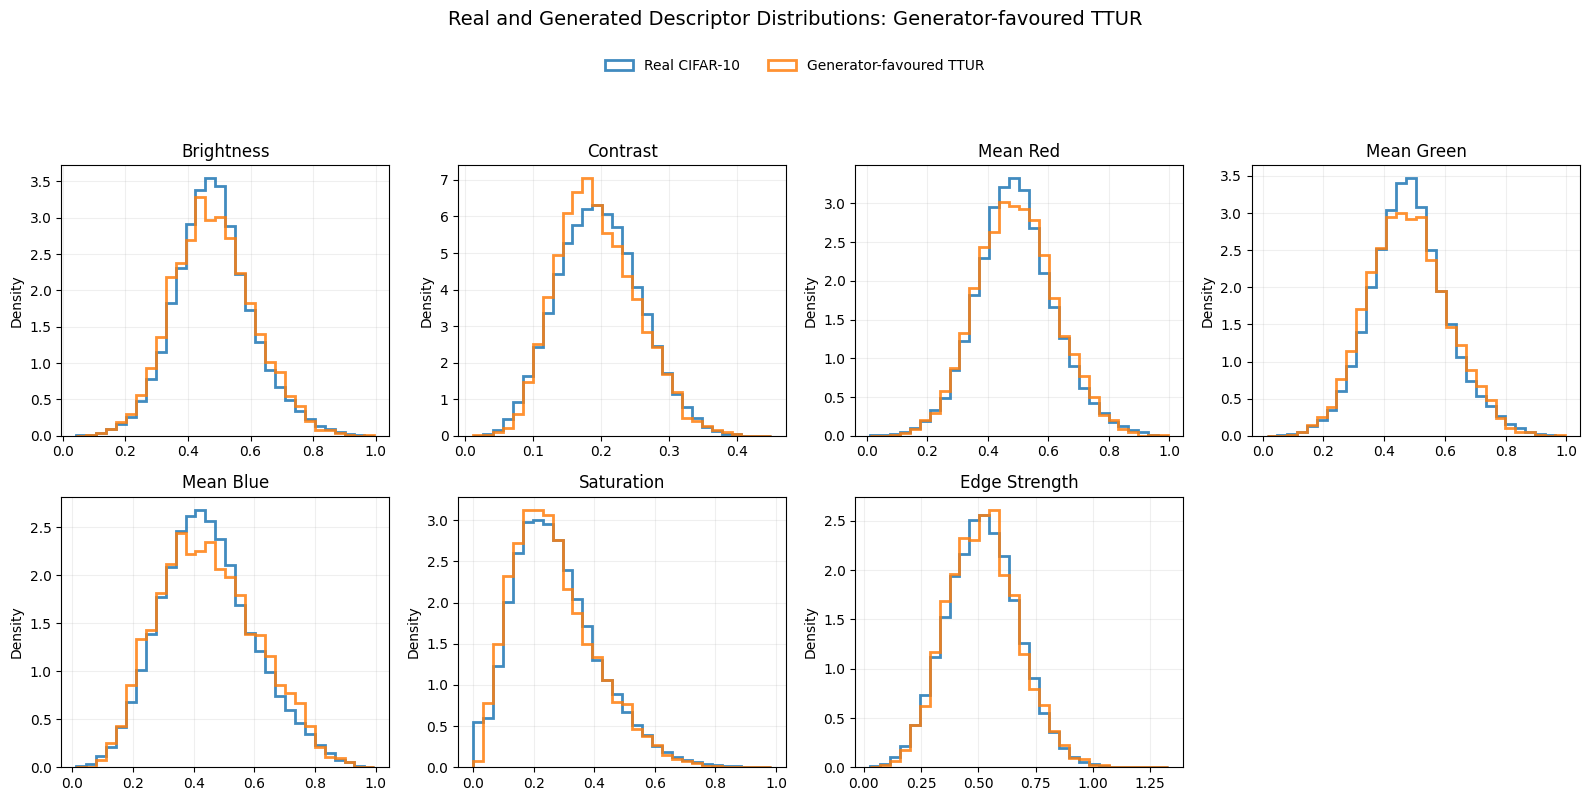

Reference descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4647,0.0169,0.1233,0.1298,1.0525
1,Contrast,0.1970,0.1957,0.0012,0.0603,0.0587,0.9741
2,Mean Red,0.4914,0.4773,0.0141,0.1284,0.1333,1.0383
3,Mean Green,0.4822,0.4654,0.0168,0.1258,0.1327,1.0553
4,Mean Blue,0.4465,0.4209,0.0256,0.1533,0.1564,1.0203
5,Saturation,0.2738,0.2764,0.0026,0.1415,0.1373,0.9702
6,Edge Strength,0.5183,0.5081,0.0102,0.1547,0.1491,0.9638


Generator-favoured TTUR descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4795,0.0020,0.1233,0.1276,1.0341
1,Contrast,0.1970,0.1943,0.0026,0.0603,0.0587,0.9731
2,Mean Red,0.4914,0.4937,0.0023,0.1284,0.1294,1.0080
3,Mean Green,0.4822,0.4784,0.0038,0.1258,0.1305,1.0373
4,Mean Blue,0.4465,0.4494,0.0029,0.1533,0.1603,1.0455
5,Saturation,0.2738,0.2679,0.0058,0.1415,0.1359,0.9606
6,Edge Strength,0.5183,0.5192,0.0008,0.1547,0.1533,0.9913


Descriptor closeness to the real training reference


,Descriptor,Reference mean error,Candidate mean error,Reference variation error,Candidate variation error,Mean closer to real,Variation closer to real
0,Brightness,0.0169,0.0020,0.0525,0.0341,Generator-favoured TTUR,Generator-favoured TTUR
1,Contrast,0.0012,0.0026,0.0259,0.0269,Reference DCGAN,Reference DCGAN
2,Mean Red,0.0141,0.0023,0.0383,0.0080,Generator-favoured TTUR,Generator-favoured TTUR
3,Mean Green,0.0168,0.0038,0.0553,0.0373,Generator-favoured TTUR,Generator-favoured TTUR
4,Mean Blue,0.0256,0.0029,0.0203,0.0455,Generator-favoured TTUR,Reference DCGAN
5,Saturation,0.0026,0.0058,0.0298,0.0394,Reference DCGAN,Reference DCGAN
6,Edge Strength,0.0102,0.0008,0.0362,0.0087,Generator-favoured TTUR,Generator-favoured TTUR


Mean closeness, Reference DCGAN: 2 of 7
Mean closeness, Generator-favoured TTUR: 5 of 7
Mean closeness, Tie: 0 of 7
Variation closeness, Reference DCGAN: 3 of 7
Variation closeness, Generator-favoured TTUR: 4 of 7
Variation closeness, Tie: 0 of 7
Reference comparison saved: [local project directory]/histories/learning_rate_ttur_reference_descriptor_comparison.csv
Candidate comparison saved: [local project directory]/histories/learning_rate_ttur_generatorfavoured_descriptor_comparison.csv
Descriptor closeness table saved: [local project directory]/histories/learning_rate_ttur_tier2_descriptor_closeness.csv
Reference descriptor plot saved: [local project directory]/grids/learning_rate_ttur_reference_descriptor_distributions.png
Candidate descriptor plot saved: [local project directory]/grids/learning_rate_ttur_generatorfavoured_descriptor_distributions.png
Protected test set remains unused.


In [75]:
required_lr_ttur_descriptor_objects = [
    "DESCRIPTOR_COLUMNS",
    "real_descriptor_df",
    "lr_ttur_reference_evaluation_images",
    "lr_ttur_candidate_evaluation_images",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "plot_descriptor_distributions",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_descriptor_objects = [
    name
    for name in required_lr_ttur_descriptor_objects
    if name not in globals()
]

assert not missing_lr_ttur_descriptor_objects, (
    "Incomplete descriptor setup:\n"
    + "\n".join(
        missing_lr_ttur_descriptor_objects
    )
)

assert real_descriptor_df.shape == (50_000, 7)

assert (
    real_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)

assert lr_ttur_reference_evaluation_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert lr_ttur_candidate_evaluation_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert (
    lr_ttur_reference_evaluation_images.dtype
    == np.uint8
)

assert (
    lr_ttur_candidate_evaluation_images.dtype
    == np.uint8
)


lr_ttur_reference_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=(
            lr_ttur_reference_evaluation_images
        ),
        batch_size=1_000,
    )
)

lr_ttur_candidate_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=(
            lr_ttur_candidate_evaluation_images
        ),
        batch_size=1_000,
    )
)


assert lr_ttur_reference_descriptor_df.shape == (
    5_000,
    7,
)

assert lr_ttur_candidate_descriptor_df.shape == (
    5_000,
    7,
)

assert (
    lr_ttur_reference_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)

assert (
    lr_ttur_candidate_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)


lr_ttur_reference_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptors=real_descriptor_df,
        generated_descriptors=(
            lr_ttur_reference_descriptor_df
        ),
    )
)

lr_ttur_candidate_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptors=real_descriptor_df,
        generated_descriptors=(
            lr_ttur_candidate_descriptor_df
        ),
    )
)


LR_TTUR_REFERENCE_DESCRIPTOR_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "reference_descriptor_comparison.csv"
    )
)

LR_TTUR_CANDIDATE_DESCRIPTOR_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "generatorfavoured_descriptor_comparison.csv"
    )
)

LR_TTUR_DESCRIPTOR_CLOSENESS_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_descriptor_closeness.csv"
    )
)

LR_TTUR_REFERENCE_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_"
        "reference_descriptor_distributions.png"
    )
)

LR_TTUR_CANDIDATE_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_"
        "generatorfavoured_descriptor_distributions.png"
    )
)


lr_ttur_reference_descriptor_comparison_df.to_csv(
    LR_TTUR_REFERENCE_DESCRIPTOR_PATH,
    index=False,
)

lr_ttur_candidate_descriptor_comparison_df.to_csv(
    LR_TTUR_CANDIDATE_DESCRIPTOR_PATH,
    index=False,
)


plot_descriptor_distributions(
    real_descriptors=real_descriptor_df,
    generated_descriptors=(
        lr_ttur_reference_descriptor_df
    ),
    model_label="Reference DCGAN",
    output_path=(
        LR_TTUR_REFERENCE_DESCRIPTOR_PLOT_PATH
    ),
    bin_count=30,
)

plot_descriptor_distributions(
    real_descriptors=real_descriptor_df,
    generated_descriptors=(
        lr_ttur_candidate_descriptor_df
    ),
    model_label="Generator-favoured TTUR",
    output_path=(
        LR_TTUR_CANDIDATE_DESCRIPTOR_PLOT_PATH
    ),
    bin_count=30,
)


lr_ttur_descriptor_closeness_df = pd.DataFrame(
    {
        "Descriptor": (
            lr_ttur_reference_descriptor_comparison_df[
                "Descriptor"
            ]
        ),
        "Reference mean error": (
            lr_ttur_reference_descriptor_comparison_df[
                "Absolute Mean Difference"
            ]
        ),
        "Candidate mean error": (
            lr_ttur_candidate_descriptor_comparison_df[
                "Absolute Mean Difference"
            ]
        ),
        "Reference variation error": np.abs(
            lr_ttur_reference_descriptor_comparison_df[
                "Generated-to-Real SD Ratio"
            ]
            - 1.0
        ),
        "Candidate variation error": np.abs(
            lr_ttur_candidate_descriptor_comparison_df[
                "Generated-to-Real SD Ratio"
            ]
            - 1.0
        ),
    }
)


lr_ttur_descriptor_closeness_df[
    "Mean closer to real"
] = np.where(
    lr_ttur_descriptor_closeness_df[
        "Candidate mean error"
    ]
    < lr_ttur_descriptor_closeness_df[
        "Reference mean error"
    ],
    "Generator-favoured TTUR",
    np.where(
        lr_ttur_descriptor_closeness_df[
            "Candidate mean error"
        ]
        > lr_ttur_descriptor_closeness_df[
            "Reference mean error"
        ],
        "Reference DCGAN",
        "Tie",
    ),
)

lr_ttur_descriptor_closeness_df[
    "Variation closer to real"
] = np.where(
    lr_ttur_descriptor_closeness_df[
        "Candidate variation error"
    ]
    < lr_ttur_descriptor_closeness_df[
        "Reference variation error"
    ],
    "Generator-favoured TTUR",
    np.where(
        lr_ttur_descriptor_closeness_df[
            "Candidate variation error"
        ]
        > lr_ttur_descriptor_closeness_df[
            "Reference variation error"
        ],
        "Reference DCGAN",
        "Tie",
    ),
)


lr_ttur_descriptor_closeness_df.to_csv(
    LR_TTUR_DESCRIPTOR_CLOSENESS_PATH,
    index=False,
)


print("Reference descriptor comparison")

display(
    lr_ttur_reference_descriptor_comparison_df.round(4)
)


print("Generator-favoured TTUR descriptor comparison")

display(
    lr_ttur_candidate_descriptor_comparison_df.round(4)
)


print(
    "Descriptor closeness to the "
    "real training reference"
)

display(
    lr_ttur_descriptor_closeness_df.round(4)
)


mean_closeness_counts = (
    lr_ttur_descriptor_closeness_df[
        "Mean closer to real"
    ].value_counts()
)

variation_closeness_counts = (
    lr_ttur_descriptor_closeness_df[
        "Variation closer to real"
    ].value_counts()
)


for model_label in [
    "Reference DCGAN",
    "Generator-favoured TTUR",
    "Tie",
]:
    print(
        f"Mean closeness, {model_label}:",
        int(
            mean_closeness_counts.get(
                model_label,
                0,
            )
        ),
        "of 7",
    )


for model_label in [
    "Reference DCGAN",
    "Generator-favoured TTUR",
    "Tie",
]:
    print(
        f"Variation closeness, {model_label}:",
        int(
            variation_closeness_counts.get(
                model_label,
                0,
            )
        ),
        "of 7",
    )


print(
    "Reference comparison saved:",
    LR_TTUR_REFERENCE_DESCRIPTOR_PATH,
)

print(
    "Candidate comparison saved:",
    LR_TTUR_CANDIDATE_DESCRIPTOR_PATH,
)

print(
    "Descriptor closeness table saved:",
    LR_TTUR_DESCRIPTOR_CLOSENESS_PATH,
)

print(
    "Reference descriptor plot saved:",
    LR_TTUR_REFERENCE_DESCRIPTOR_PLOT_PATH,
)

print(
    "Candidate descriptor plot saved:",
    LR_TTUR_CANDIDATE_DESCRIPTOR_PLOT_PATH,
)

print("Protected test set remains unused.")

#### Low-Level Descriptor Finding

Both shortlisted configurations broadly reproduce the low-level brightness, colour, contrast, saturation and edge-strength distributions of the real CIFAR-10 training images. The substantial overlap across the density-normalised histograms indicates that neither model has a major low-level distribution failure.

The generator-favoured TTUR candidate is closer to the real descriptor mean for five of the seven descriptors:

| Descriptor | Reference mean error | Candidate mean error | Closer model |
|---|---:|---:|---|
| Brightness | `0.0169` | `0.0020` | Generator-favoured TTUR |
| Contrast | `0.0012` | `0.0026` | Reference DCGAN |
| Mean red | `0.0141` | `0.0023` | Generator-favoured TTUR |
| Mean green | `0.0168` | `0.0038` | Generator-favoured TTUR |
| Mean blue | `0.0256` | `0.0029` | Generator-favoured TTUR |
| Saturation | `0.0026` | `0.0058` | Reference DCGAN |
| Edge strength | `0.0102` | `0.0008` | Generator-favoured TTUR |

The largest candidate improvements occur in brightness and the three mean colour channels. The reference outputs are slightly darker than the real images and have lower mean red, green and especially blue intensity. The candidate substantially reduces these shifts. Its edge-strength mean of `0.5192` is also nearly identical to the real mean of `0.5183`, whereas the reference is slightly lower at `0.5081`.

The candidate is also closer to the real descriptor variation for four of the seven descriptors. Its strongest variation matches are mean red and edge strength, with generated-to-real standard-deviation ratios of `1.0080` and `0.9913`. The reference is marginally closer for contrast and saturation and more clearly closer for mean blue variation. Therefore, the candidate's improved blue-channel mean is accompanied by a somewhat wider-than-real blue distribution.

Overall, the descriptor evidence favours the generator-favoured TTUR candidate. It provides substantially better alignment in overall brightness, RGB balance and edge strength while retaining broadly realistic variation. The reference remains slightly better for contrast and saturation, so the candidate is not uniformly closer on every low-level property.

This is meaningful supporting evidence because it agrees with the candidate's lower repeated FID, improved manual-quality counts and slightly stronger classifier-supported coverage. However, descriptor similarity measures only low-level image statistics. It does not establish better object recognisability, semantic class correctness or feature-space diversity by itself.

The descriptor result therefore strengthens the candidate's Tier 2 case but does not yet trigger adoption or seed-123 confirmation. Diversity, repetition, stability and compute evidence are still required before the final learning-rate and TTUR decision.

### 10.11 Diversity and Repetition

The reference DCGAN and generator-favoured TTUR candidate are now compared for generated-to-generated diversity and repetition.

The same 5,000-image evaluation pools from Section 10.9 are reused. InceptionV3 features are extracted for both pools, after which ten matched random subsets of 1,000 generated images are evaluated against independently sampled real CIFAR-10 training subsets.

For every repeat, the analysis reports:

- mean and median pairwise cosine distance;
- median and minimum nearest-neighbour distance;
- generated-to-real diversity ratio;
- near-duplicate rate using the corresponding real subset's first-percentile nearest-neighbour distance as the threshold.

The same generated subset indices are used for both models within each repeat, enabling a paired comparison. Exact pixel duplicates are separately checked across each complete 5,000-image pool.

This measures generated-to-generated diversity and possible mode collapse. It is not the formal generated-to-training memorisation audit, which remains reserved for Notebook 4.

In [78]:
required_lr_ttur_diversity_objects = [
    "SECTION6_DIVERSITY_HELPER_READY",
    "compact_cosine_diversity_summary",
    "extract_inception_features",
    "fid_feature_extractor",
    "real_fid_features",
    "FID_FEATURE_DIM",
    "FID_BATCH_SIZE",
    "SELECTED_EVALUATION_SAMPLE_COUNT",
    "DIVERSITY_SUBSET_SIZE",
    "DIVERSITY_REPEATS",
    "REAL_DIVERSITY_SEED",
    "GENERATED_DIVERSITY_SEED",
    "NEAR_DUPLICATE_PERCENTILE",
    "lr_ttur_reference_evaluation_images",
    "lr_ttur_candidate_evaluation_images",
    "HISTORIES_DIR",
]

missing_lr_ttur_diversity_objects = [
    name
    for name in required_lr_ttur_diversity_objects
    if name not in globals()
]

assert not missing_lr_ttur_diversity_objects, (
    "Incomplete diversity setup:\n"
    + "\n".join(
        missing_lr_ttur_diversity_objects
    )
)

assert SECTION6_DIVERSITY_HELPER_READY
assert callable(
    compact_cosine_diversity_summary
)

assert lr_ttur_reference_evaluation_images.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    32,
    32,
    3,
)

assert lr_ttur_candidate_evaluation_images.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    32,
    32,
    3,
)

assert lr_ttur_reference_evaluation_images.dtype == np.uint8
assert lr_ttur_candidate_evaluation_images.dtype == np.uint8


# Extract features once for each complete
# 5,000-image generated evaluation pool.
lr_ttur_reference_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            lr_ttur_reference_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )
)

lr_ttur_candidate_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            lr_ttur_candidate_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )
)


assert lr_ttur_reference_evaluation_features.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    FID_FEATURE_DIM,
)

assert lr_ttur_candidate_evaluation_features.shape == (
    SELECTED_EVALUATION_SAMPLE_COUNT,
    FID_FEATURE_DIM,
)

assert np.isfinite(
    lr_ttur_reference_evaluation_features
).all()

assert np.isfinite(
    lr_ttur_candidate_evaluation_features
).all()


lr_ttur_real_diversity_rng = np.random.default_rng(
    REAL_DIVERSITY_SEED
)

lr_ttur_generated_diversity_rng = (
    np.random.default_rng(
        GENERATED_DIVERSITY_SEED
    )
)

lr_ttur_diversity_repeat_rows = []

# Retain the first matched repeat for the
# later nearest-neighbour visual analysis.
lr_ttur_diversity_representative = None


for repeat_index in range(
    1,
    DIVERSITY_REPEATS + 1,
):
    real_indices = (
        lr_ttur_real_diversity_rng.choice(
            len(real_fid_features),
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        lr_ttur_generated_diversity_rng.choice(
            SELECTED_EVALUATION_SAMPLE_COUNT,
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    real_summary = (
        compact_cosine_diversity_summary(
            real_fid_features[
                real_indices
            ]
        )
    )

    reference_summary = (
        compact_cosine_diversity_summary(
            lr_ttur_reference_evaluation_features[
                generated_indices
            ]
        )
    )

    candidate_summary = (
        compact_cosine_diversity_summary(
            lr_ttur_candidate_evaluation_features[
                generated_indices
            ]
        )
    )

    near_duplicate_threshold = float(
        np.percentile(
            real_summary[
                "nearest_distances"
            ],
            NEAR_DUPLICATE_PERCENTILE,
        )
    )

    repeat_summaries = {
        "Real CIFAR-10": real_summary,
        "Reference DCGAN": reference_summary,
        "Generator-favoured TTUR": (
            candidate_summary
        ),
    }

    for configuration, summary in (
        repeat_summaries.items()
    ):
        if configuration == "Real CIFAR-10":
            diversity_ratio = 1.0
        else:
            diversity_ratio = float(
                summary[
                    "mean_pairwise_distance"
                ]
                / real_summary[
                    "mean_pairwise_distance"
                ]
            )

        near_duplicate_rate = float(
            np.mean(
                summary[
                    "nearest_distances"
                ]
                < near_duplicate_threshold
            )
            * 100.0
        )

        lr_ttur_diversity_repeat_rows.append(
            {
                "Repeat": repeat_index,
                "Configuration": configuration,
                "Feature sample count": (
                    DIVERSITY_SUBSET_SIZE
                ),
                "Mean pairwise distance": (
                    summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Median pairwise distance": (
                    summary[
                        "median_pairwise_distance"
                    ]
                ),
                "Median nearest distance": (
                    summary[
                        "median_nearest_distance"
                    ]
                ),
                "Minimum nearest distance": (
                    summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-duplicate threshold": (
                    near_duplicate_threshold
                ),
                "Near-duplicate rate (%)": (
                    near_duplicate_rate
                ),
                "Diversity ratio to real": (
                    diversity_ratio
                ),
            }
        )

    if repeat_index == 1:
        lr_ttur_diversity_representative = {
            "generated_indices": (
                generated_indices.copy()
            ),
            "real_nearest_distances": (
                real_summary[
                    "nearest_distances"
                ].copy()
            ),
            "reference_nearest_distances": (
                reference_summary[
                    "nearest_distances"
                ].copy()
            ),
            "candidate_nearest_distances": (
                candidate_summary[
                    "nearest_distances"
                ].copy()
            ),
            "near_duplicate_threshold": (
                near_duplicate_threshold
            ),
        }


lr_ttur_diversity_repeats_df = pd.DataFrame(
    lr_ttur_diversity_repeat_rows
)

assert len(
    lr_ttur_diversity_repeats_df
) == DIVERSITY_REPEATS * 3

assert lr_ttur_diversity_representative is not None


lr_ttur_diversity_summary_df = (
    lr_ttur_diversity_repeats_df
    .groupby(
        "Configuration",
        as_index=False,
    )
    .agg(
        mean_pairwise_distance_mean=(
            "Mean pairwise distance",
            "mean",
        ),
        mean_pairwise_distance_sd=(
            "Mean pairwise distance",
            "std",
        ),
        median_pairwise_distance_mean=(
            "Median pairwise distance",
            "mean",
        ),
        median_nearest_distance_mean=(
            "Median nearest distance",
            "mean",
        ),
        minimum_nearest_distance_mean=(
            "Minimum nearest distance",
            "mean",
        ),
        near_duplicate_rate_mean=(
            "Near-duplicate rate (%)",
            "mean",
        ),
        near_duplicate_rate_sd=(
            "Near-duplicate rate (%)",
            "std",
        ),
        diversity_ratio_mean=(
            "Diversity ratio to real",
            "mean",
        ),
        diversity_ratio_sd=(
            "Diversity ratio to real",
            "std",
        ),
    )
)


# Check exact pixel duplicates across each
# complete 5,000-image generated pool.
lr_ttur_reference_flat_images = (
    lr_ttur_reference_evaluation_images.reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

lr_ttur_candidate_flat_images = (
    lr_ttur_candidate_evaluation_images.reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

lr_ttur_reference_unique_count = int(
    np.unique(
        lr_ttur_reference_flat_images,
        axis=0,
    ).shape[0]
)

lr_ttur_candidate_unique_count = int(
    np.unique(
        lr_ttur_candidate_flat_images,
        axis=0,
    ).shape[0]
)

lr_ttur_reference_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - lr_ttur_reference_unique_count
)

lr_ttur_candidate_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - lr_ttur_candidate_unique_count
)

lr_ttur_exact_duplicate_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference DCGAN",
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Unique images": (
                lr_ttur_reference_unique_count
            ),
            "Exact duplicates": (
                lr_ttur_reference_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                lr_ttur_reference_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
        {
            "Configuration": (
                "Generator-favoured TTUR"
            ),
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Unique images": (
                lr_ttur_candidate_unique_count
            ),
            "Exact duplicates": (
                lr_ttur_candidate_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                lr_ttur_candidate_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
    ]
)


LR_TTUR_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_diversity_repeats.csv"
    )
)

LR_TTUR_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_diversity_summary.csv"
    )
)

LR_TTUR_EXACT_DUPLICATE_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_exact_duplicates.csv"
    )
)


lr_ttur_diversity_repeats_df.to_csv(
    LR_TTUR_DIVERSITY_REPEATS_PATH,
    index=False,
)

lr_ttur_diversity_summary_df.to_csv(
    LR_TTUR_DIVERSITY_SUMMARY_PATH,
    index=False,
)

lr_ttur_exact_duplicate_df.to_csv(
    LR_TTUR_EXACT_DUPLICATE_PATH,
    index=False,
)


display(
    lr_ttur_diversity_summary_df.round(6)
)

display(
    lr_ttur_exact_duplicate_df.round(6)
)


reference_diversity_ratios = (
    lr_ttur_diversity_repeats_df.loc[
        lr_ttur_diversity_repeats_df[
            "Configuration"
        ] == "Reference DCGAN",
        "Diversity ratio to real",
    ].to_numpy()
)

candidate_diversity_ratios = (
    lr_ttur_diversity_repeats_df.loc[
        lr_ttur_diversity_repeats_df[
            "Configuration"
        ] == "Generator-favoured TTUR",
        "Diversity ratio to real",
    ].to_numpy()
)

candidate_ratio_advantages = (
    np.abs(
        reference_diversity_ratios - 1.0
    )
    - np.abs(
        candidate_diversity_ratios - 1.0
    )
)


reference_near_duplicate_rates = (
    lr_ttur_diversity_repeats_df.loc[
        lr_ttur_diversity_repeats_df[
            "Configuration"
        ] == "Reference DCGAN",
        "Near-duplicate rate (%)",
    ].to_numpy()
)

candidate_near_duplicate_rates = (
    lr_ttur_diversity_repeats_df.loc[
        lr_ttur_diversity_repeats_df[
            "Configuration"
        ] == "Generator-favoured TTUR",
        "Near-duplicate rate (%)",
    ].to_numpy()
)


print(
    "Completed matched diversity repeats:",
    DIVERSITY_REPEATS,
)

print(
    "Repeats where candidate diversity ratio "
    "was closer to real:",
    int(
        np.sum(
            candidate_ratio_advantages > 0
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Mean candidate improvement in absolute "
    "diversity-ratio error:",
    f"{candidate_ratio_advantages.mean():.6f}",
)

print(
    "Repeats where candidate had a lower "
    "near-duplicate rate:",
    int(
        np.sum(
            candidate_near_duplicate_rates
            < reference_near_duplicate_rates
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Repeats where near-duplicate rates tied:",
    int(
        np.sum(
            candidate_near_duplicate_rates
            == reference_near_duplicate_rates
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Repeat-level results saved:",
    LR_TTUR_DIVERSITY_REPEATS_PATH,
)

print(
    "Diversity summary saved:",
    LR_TTUR_DIVERSITY_SUMMARY_PATH,
)

print(
    "Exact-duplicate results saved:",
    LR_TTUR_EXACT_DUPLICATE_PATH,
)

print("Protected test set remains unused.")


del lr_ttur_reference_flat_images
del lr_ttur_candidate_flat_images

gc.collect()

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

,Configuration,mean_pairwise_distance_mean,mean_pairwise_distance_sd,median_pairwise_distance_mean,median_nearest_distance_mean,minimum_nearest_distance_mean,near_duplicate_rate_mean,near_duplicate_rate_sd,diversity_ratio_mean,diversity_ratio_sd
0,Generator-favoured TTUR,0.350775,0.002235,0.349191,0.196994,0.113740,0.00,0.00000,0.932519,0.006250
1,Real CIFAR-10,0.376167,0.002501,0.378124,0.195888,0.061053,0.96,0.05164,1.000000,0.000000
2,Reference DCGAN,0.351327,0.001756,0.349983,0.196041,0.119539,0.00,0.00000,0.934004,0.007671


,Configuration,Image sample count,Unique images,Exact duplicates,Exact-duplicate rate (%)
0,Reference DCGAN,5000,5000,0,0.0
1,Generator-favoured TTUR,5000,5000,0,0.0


Completed matched diversity repeats: 10
Repeats where candidate diversity ratio was closer to real: 2 of 10
Mean candidate improvement in absolute diversity-ratio error: -0.001485
Repeats where candidate had a lower near-duplicate rate: 0 of 10
Repeats where near-duplicate rates tied: 10 of 10
Repeat-level results saved: [local project directory]/histories/learning_rate_ttur_tier2_diversity_repeats.csv
Diversity summary saved: [local project directory]/histories/learning_rate_ttur_tier2_diversity_summary.csv
Exact-duplicate results saved: [local project directory]/histories/learning_rate_ttur_tier2_exact_duplicates.csv
Protected test set remains unused.


45008

#### Nearest-Neighbour Distance and Closest-Pair Inspection

The first matched diversity repeat is used for a closer inspection of generated-to-generated repetition.

The analysis includes:

- empirical cumulative distributions of nearest-neighbour cosine distances;
- the real-data first-percentile near-duplicate threshold;
- the ten closest unique generated-image pairs for the reference and generator-favoured TTUR candidate.

The distance distribution checks whether similar aggregate diversity ratios conceal a broader shift toward tightly clustered outputs. The image panels then show what the smallest feature-space distances represent visually.

This remains a generated-to-generated diversity and repetition analysis. It does not compare generated images against the training set and is not the formal memorisation audit reserved for Notebook 4.

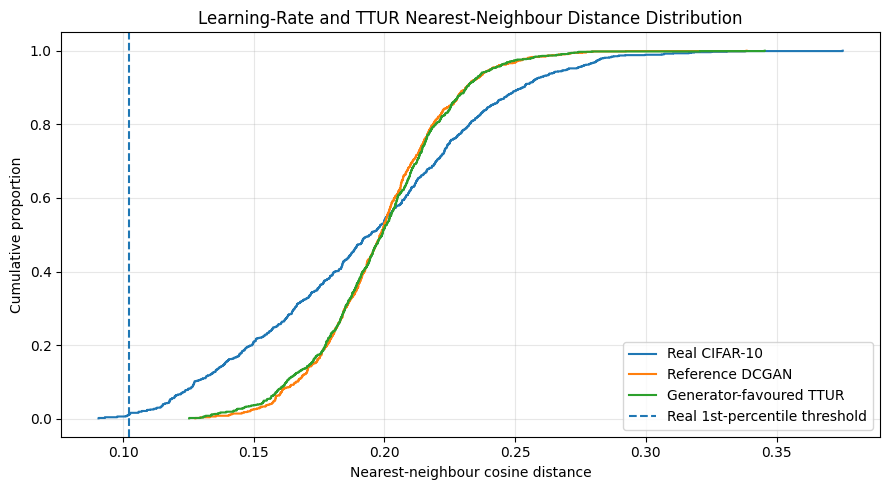

Saved nearest-distance plot: [local project directory]/grids/learning_rate_ttur_tier2_nearest_distance_ecdf.png
Near-duplicate threshold: 0.102203
Protected test set remains unused.


In [81]:
LR_TTUR_NEAREST_DISTANCE_PLOT_PATH = (
    GRIDS_DIR
    / (
        "learning_rate_ttur_tier2_"
        "nearest_distance_ecdf.png"
    )
)

lr_ttur_real_nearest_distances = (
    lr_ttur_diversity_representative[
        "real_nearest_distances"
    ]
)

lr_ttur_reference_nearest_distances = (
    lr_ttur_diversity_representative[
        "reference_nearest_distances"
    ]
)

lr_ttur_candidate_nearest_distances = (
    lr_ttur_diversity_representative[
        "candidate_nearest_distances"
    ]
)

lr_ttur_near_duplicate_threshold = float(
    lr_ttur_diversity_representative[
        "near_duplicate_threshold"
    ]
)


lr_ttur_real_sorted_distances = np.sort(
    lr_ttur_real_nearest_distances
)

lr_ttur_reference_sorted_distances = np.sort(
    lr_ttur_reference_nearest_distances
)

lr_ttur_candidate_sorted_distances = np.sort(
    lr_ttur_candidate_nearest_distances
)


lr_ttur_real_ecdf = np.arange(
    1,
    len(lr_ttur_real_sorted_distances) + 1,
) / len(lr_ttur_real_sorted_distances)

lr_ttur_reference_ecdf = np.arange(
    1,
    len(lr_ttur_reference_sorted_distances) + 1,
) / len(lr_ttur_reference_sorted_distances)

lr_ttur_candidate_ecdf = np.arange(
    1,
    len(lr_ttur_candidate_sorted_distances) + 1,
) / len(lr_ttur_candidate_sorted_distances)


plt.figure(figsize=(9, 5))

plt.step(
    lr_ttur_real_sorted_distances,
    lr_ttur_real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    lr_ttur_reference_sorted_distances,
    lr_ttur_reference_ecdf,
    where="post",
    label="Reference DCGAN",
)

plt.step(
    lr_ttur_candidate_sorted_distances,
    lr_ttur_candidate_ecdf,
    where="post",
    label="Generator-favoured TTUR",
)

plt.axvline(
    lr_ttur_near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "Learning-Rate and TTUR "
    "Nearest-Neighbour Distance Distribution"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    LR_TTUR_NEAREST_DISTANCE_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Saved nearest-distance plot:",
    LR_TTUR_NEAREST_DISTANCE_PLOT_PATH,
)

print(
    "Near-duplicate threshold:",
    f"{lr_ttur_near_duplicate_threshold:.6f}",
)

print("Protected test set remains unused.")

In [82]:
lr_ttur_representative_indices = (
    lr_ttur_diversity_representative[
        "generated_indices"
    ]
)

lr_ttur_reference_pair_features = (
    lr_ttur_reference_evaluation_features[
        lr_ttur_representative_indices
    ]
)

lr_ttur_candidate_pair_features = (
    lr_ttur_candidate_evaluation_features[
        lr_ttur_representative_indices
    ]
)

lr_ttur_reference_pair_images = (
    lr_ttur_reference_evaluation_images[
        lr_ttur_representative_indices
    ]
)

lr_ttur_candidate_pair_images = (
    lr_ttur_candidate_evaluation_images[
        lr_ttur_representative_indices
    ]
)


lr_ttur_reference_feature_norms = np.maximum(
    np.linalg.norm(
        lr_ttur_reference_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)

lr_ttur_candidate_feature_norms = np.maximum(
    np.linalg.norm(
        lr_ttur_candidate_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)


lr_ttur_reference_normalised_features = (
    lr_ttur_reference_pair_features
    / lr_ttur_reference_feature_norms
)

lr_ttur_candidate_normalised_features = (
    lr_ttur_candidate_pair_features
    / lr_ttur_candidate_feature_norms
)


lr_ttur_reference_distance_matrix = np.clip(
    1.0
    - (
        lr_ttur_reference_normalised_features
        @ lr_ttur_reference_normalised_features.T
    ),
    0.0,
    2.0,
)

lr_ttur_candidate_distance_matrix = np.clip(
    1.0
    - (
        lr_ttur_candidate_normalised_features
        @ lr_ttur_candidate_normalised_features.T
    ),
    0.0,
    2.0,
)

np.fill_diagonal(
    lr_ttur_reference_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    lr_ttur_candidate_distance_matrix,
    np.inf,
)

assert lr_ttur_reference_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

assert lr_ttur_candidate_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

print(
    "Matched nearest-neighbour "
    "distance matrices ready."
)

Matched nearest-neighbour distance matrices ready.


In [83]:
lr_ttur_representative_indices = (
    lr_ttur_diversity_representative[
        "generated_indices"
    ]
)

lr_ttur_reference_pair_features = (
    lr_ttur_reference_evaluation_features[
        lr_ttur_representative_indices
    ]
)

lr_ttur_candidate_pair_features = (
    lr_ttur_candidate_evaluation_features[
        lr_ttur_representative_indices
    ]
)

lr_ttur_reference_pair_images = (
    lr_ttur_reference_evaluation_images[
        lr_ttur_representative_indices
    ]
)

lr_ttur_candidate_pair_images = (
    lr_ttur_candidate_evaluation_images[
        lr_ttur_representative_indices
    ]
)


lr_ttur_reference_feature_norms = np.maximum(
    np.linalg.norm(
        lr_ttur_reference_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)

lr_ttur_candidate_feature_norms = np.maximum(
    np.linalg.norm(
        lr_ttur_candidate_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)


lr_ttur_reference_normalised_features = (
    lr_ttur_reference_pair_features
    / lr_ttur_reference_feature_norms
)

lr_ttur_candidate_normalised_features = (
    lr_ttur_candidate_pair_features
    / lr_ttur_candidate_feature_norms
)


lr_ttur_reference_distance_matrix = np.clip(
    1.0
    - (
        lr_ttur_reference_normalised_features
        @ lr_ttur_reference_normalised_features.T
    ),
    0.0,
    2.0,
)

lr_ttur_candidate_distance_matrix = np.clip(
    1.0
    - (
        lr_ttur_candidate_normalised_features
        @ lr_ttur_candidate_normalised_features.T
    ),
    0.0,
    2.0,
)

np.fill_diagonal(
    lr_ttur_reference_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    lr_ttur_candidate_distance_matrix,
    np.inf,
)

assert lr_ttur_reference_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

assert lr_ttur_candidate_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

print(
    "Matched nearest-neighbour "
    "distance matrices ready."
)

Matched nearest-neighbour distance matrices ready.


In [84]:
lr_ttur_pair_configurations = [
    {
        "label": "Reference DCGAN",
        "images": (
            lr_ttur_reference_pair_images
        ),
        "distance_matrix": (
            lr_ttur_reference_distance_matrix
        ),
        "output_path": (
            GRIDS_DIR
            / (
                "learning_rate_ttur_tier2_"
                "reference_most_similar_pairs.png"
            )
        ),
    },
    {
        "label": "Generator-favoured TTUR",
        "images": (
            lr_ttur_candidate_pair_images
        ),
        "distance_matrix": (
            lr_ttur_candidate_distance_matrix
        ),
        "output_path": (
            GRIDS_DIR
            / (
                "learning_rate_ttur_tier2_"
                "generatorfavoured_"
                "most_similar_pairs.png"
            )
        ),
    },
]


lr_ttur_pair_summary_rows = []

for configuration in (
    lr_ttur_pair_configurations
):
    label = configuration["label"]
    images = configuration["images"]

    distance_matrix = configuration[
        "distance_matrix"
    ]

    output_path = configuration[
        "output_path"
    ]

    nearest_indices = np.argmin(
        distance_matrix,
        axis=1,
    )

    unique_pair_distances = {}

    for image_index, neighbour_index in enumerate(
        nearest_indices
    ):
        pair = tuple(
            sorted(
                (
                    int(image_index),
                    int(neighbour_index),
                )
            )
        )

        pair_distance = float(
            distance_matrix[
                pair[0],
                pair[1],
            ]
        )

        if pair not in unique_pair_distances:
            unique_pair_distances[pair] = (
                pair_distance
            )

    most_similar_pairs = sorted(
        unique_pair_distances.items(),
        key=lambda item: item[1],
    )[:10]

    assert len(most_similar_pairs) == 10

    fig, axes = plt.subplots(
        5,
        4,
        figsize=(10, 13),
    )

    for pair_number, (
        pair,
        pair_distance,
    ) in enumerate(most_similar_pairs):
        row = pair_number // 2
        column = (
            pair_number % 2
        ) * 2

        first_index, second_index = pair

        axes[row, column].imshow(
            images[first_index]
        )

        axes[row, column].set_title(
            f"Pair {pair_number + 1}A",
            fontsize=9,
        )

        axes[row, column].axis("off")

        axes[row, column + 1].imshow(
            images[second_index]
        )

        axes[row, column + 1].set_title(
            (
                f"Pair {pair_number + 1}B\n"
                f"Distance: {pair_distance:.4f}"
            ),
            fontsize=9,
        )

        axes[row, column + 1].axis("off")

        lr_ttur_pair_summary_rows.append(
            {
                "Configuration": label,
                "Pair": pair_number + 1,
                "First subset index": (
                    first_index
                ),
                "Second subset index": (
                    second_index
                ),
                "First pool index": int(
                    lr_ttur_representative_indices[
                        first_index
                    ]
                ),
                "Second pool index": int(
                    lr_ttur_representative_indices[
                        second_index
                    ]
                ),
                "Cosine distance": (
                    pair_distance
                ),
            }
        )

    fig.suptitle(
        (
            f"{label} Most Similar "
            "Generated Pairs"
        ),
        fontsize=14,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.97)
    )

    fig.savefig(
        output_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved {label} pair figure:",
        output_path,
    )


lr_ttur_closest_pair_summary_df = (
    pd.DataFrame(
        lr_ttur_pair_summary_rows
    )
)

LR_TTUR_CLOSEST_PAIR_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_tier2_"
        "closest_pairs.csv"
    )
)

lr_ttur_closest_pair_summary_df.to_csv(
    LR_TTUR_CLOSEST_PAIR_SUMMARY_PATH,
    index=False,
)

display(
    lr_ttur_closest_pair_summary_df.round(6)
)

print(
    "Closest-pair summary saved:",
    LR_TTUR_CLOSEST_PAIR_SUMMARY_PATH,
)

print("Protected test set remains unused.")

Saved Reference DCGAN pair figure: [local project directory]/grids/learning_rate_ttur_tier2_reference_most_similar_pairs.png


Saved Generator-favoured TTUR pair figure: [local project directory]/grids/learning_rate_ttur_tier2_generatorfavoured_most_similar_pairs.png


,Configuration,Pair,First subset index,Second subset index,First pool index,Second pool index,Cosine distance
0,Reference DCGAN,1,75,424,2497,1704,0.127625
1,Reference DCGAN,2,655,731,3531,145,0.129681
2,Reference DCGAN,3,268,688,2122,821,0.133227
3,Reference DCGAN,4,825,951,4238,3101,0.135524
4,Reference DCGAN,5,471,764,4793,3112,0.140402
5,Reference DCGAN,6,181,925,2459,927,0.141034
6,Reference DCGAN,7,393,968,666,3155,0.141765
7,Reference DCGAN,8,123,832,2495,901,0.145418
8,Reference DCGAN,9,778,917,2748,2106,0.146226
9,Reference DCGAN,10,108,123,1457,2495,0.147419


Closest-pair summary saved: [local project directory]/histories/learning_rate_ttur_tier2_closest_pairs.csv
Protected test set remains unused.


#### Diversity and Repetition Finding

Both configurations retain strong generated-to-generated diversity and show no evidence of exact duplication or severe mode collapse.

Across ten matched 1,000-image feature subsets, the reference DCGAN achieved a mean diversity ratio of `0.9340`, while the generator-favoured TTUR candidate achieved `0.9325`. Both values are slightly below the real CIFAR-10 reference of `1.0000`, indicating that both generated distributions are modestly less dispersed than the real training distribution.

The reference was closer to the real diversity ratio in eight of the ten repeats. The candidate's mean improvement in absolute diversity-ratio error was `-0.001485`, so this evidence gives the reference a very small diversity advantage. The difference is minor, however, and does not indicate a meaningful practical separation between the models.

The nearest-neighbour results support the same conclusion. Median nearest-neighbour distances were almost identical:

- real CIFAR-10: `0.1959`;
- reference DCGAN: `0.1960`;
- generator-favoured TTUR: `0.1970`.

The generated ECDF curves also overlap closely. Neither model produced samples below the real-data first-percentile near-duplicate threshold of `0.1022`, giving both models a `0%` near-duplicate rate across all ten repeats. Both complete 5,000-image pools also contained `5,000` unique images and no exact pixel duplicates.

The closest-pair panels confirm that low feature-space distances generally represent images sharing broad colours, backgrounds, viewpoints or object structure rather than duplicated outputs. The reference pairs include repeated visual themes such as vehicles, aircraft and animal-like forms, but the paired images remain visibly distinct.

The candidate also avoids direct duplication, although several of its closest relationships are concentrated around recurring vehicle-like or building-like structures. A few images appear in more than one closest-pair relationship because they act as local feature-space neighbours for multiple samples. This suggests some local clustering, but not a collapse into identical or near-identical outputs.

Overall, diversity and repetition evidence slightly favours the reference DCGAN, but only weakly. Both configurations remain acceptably diverse, have no detected exact or near duplicates, and show no convincing mode-collapse warning. This result therefore acts mainly as a safeguard: the generator-favoured TTUR candidate's gains in FID, manual quality, coverage and descriptor alignment were not obtained through an obvious loss of diversity.

The TTUR decision remains unresolved until stability and compute evidence are consolidated.

### 10.12 Stability and Compute Consolidation

The reference DCGAN and generator-favoured TTUR candidate used the same:

- generator and discriminator architectures;
- 100-epoch training budget;
- batch size of 64;
- 782 batches per epoch;
- one discriminator and one generator update per batch;
- total update exposure of 78,200 updates per network;
- CIFAR-10 training data and preprocessing;
- checkpoint and progression-grid schedule.

The only intentional difference was the discriminator learning rate:

- reference: generator `2e-4`, discriminator `2e-4`;
- generator-favoured TTUR: generator `2e-4`, discriminator `1e-4`.

The complete trajectories are compared again for the Tier 2 finalists. The final 20 epochs are summarised to examine late generator loss, discriminator loss, real and generated scores, score separation and epoch time.

The score separation is calculated as:

```mean real score - mean generated score```

A larger separation indicates that the discriminator distinguishes real and generated images more strongly. This is a balance diagnostic rather than a direct image-quality measure.

Training time is reconstructed from each persisted history CSV. No official CIFAR-10 test image is used.

In [87]:
required_lr_ttur_stability_objects = [
    "LR_TTUR_TIER2_REFERENCE_RUN_ID",
    "LR_TTUR_TIER2_CANDIDATE_RUN_ID",
    "LR_TTUR_REFERENCE_GENERATOR_LR",
    "LR_TTUR_REFERENCE_DISCRIMINATOR_LR",
    "LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR",
    "LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR",
    "LR_TTUR_BATCH_SIZE",
    "LR_TTUR_BATCHES_PER_EPOCH",
    "LR_TTUR_EXPECTED_UPDATES",
    "LR_TTUR_TARGET_EPOCHS",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "HISTORIES_DIR",
]

missing_lr_ttur_stability_objects = [
    name
    for name in required_lr_ttur_stability_objects
    if name not in globals()
]

assert not missing_lr_ttur_stability_objects, (
    "Incomplete stability and compute setup:\n"
    + "\n".join(
        missing_lr_ttur_stability_objects
    )
)


LR_TTUR_STABILITY_REQUIRED_COLUMNS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

LR_TTUR_PREVIOUS_LATE_START = 61
LR_TTUR_PREVIOUS_LATE_END = 80

LR_TTUR_FINAL_LATE_START = 81
LR_TTUR_FINAL_LATE_END = 100


assert LR_TTUR_BATCH_SIZE == 64
assert LR_TTUR_BATCHES_PER_EPOCH == 782
assert LR_TTUR_EXPECTED_UPDATES == 78_200
assert LR_TTUR_TARGET_EPOCHS == 100


lr_ttur_tier2_stability_specs = [
    {
        "Configuration": "Reference DCGAN",
        "Run ID": (
            LR_TTUR_TIER2_REFERENCE_RUN_ID
        ),
        "Generator LR": (
            LR_TTUR_REFERENCE_GENERATOR_LR
        ),
        "Discriminator LR": (
            LR_TTUR_REFERENCE_DISCRIMINATOR_LR
        ),
    },
    {
        "Configuration": (
            "Generator-favoured TTUR"
        ),
        "Run ID": (
            LR_TTUR_TIER2_CANDIDATE_RUN_ID
        ),
        "Generator LR": (
            LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
        ),
        "Discriminator LR": (
            LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
        ),
    },
]


lr_ttur_tier2_history_frames = {}
lr_ttur_stability_rows = []


for specification in (
    lr_ttur_tier2_stability_specs
):
    configuration = specification[
        "Configuration"
    ]

    run_id = specification["Run ID"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    assert history_path.is_file(), (
        "Missing Tier 2 history:\n"
        f"{history_path}"
    )


    history_df = pd.read_csv(
        history_path
    )


    missing_history_columns = [
        column
        for column
        in LR_TTUR_STABILITY_REQUIRED_COLUMNS
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{run_id} is missing columns:\n"
        + "\n".join(
            missing_history_columns
        )
    )


    history_df = (
        history_df[
            LR_TTUR_STABILITY_REQUIRED_COLUMNS
        ]
        .copy()
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    assert len(history_df) == 100

    assert np.array_equal(
        history_df[
            "epoch"
        ].to_numpy(dtype=np.int64),
        np.arange(
            1,
            101,
            dtype=np.int64,
        ),
    )

    assert np.isfinite(
        history_df[
            LR_TTUR_STABILITY_REQUIRED_COLUMNS
        ].to_numpy(dtype=np.float64)
    ).all()


    previous_late_df = history_df.loc[
        history_df["epoch"].between(
            LR_TTUR_PREVIOUS_LATE_START,
            LR_TTUR_PREVIOUS_LATE_END,
        )
    ].copy()

    final_late_df = history_df.loc[
        history_df["epoch"].between(
            LR_TTUR_FINAL_LATE_START,
            LR_TTUR_FINAL_LATE_END,
        )
    ].copy()


    assert len(previous_late_df) == 20
    assert len(final_late_df) == 20


    previous_score_separation = float(
        (
            previous_late_df["real_score"]
            - previous_late_df["fake_score"]
        ).mean()
    )

    final_score_separation = float(
        (
            final_late_df["real_score"]
            - final_late_df["fake_score"]
        ).mean()
    )


    lr_ttur_stability_rows.append(
        {
            "Configuration": configuration,
            "Run ID": run_id,
            "Generator LR": (
                specification["Generator LR"]
            ),
            "Discriminator LR": (
                specification[
                    "Discriminator LR"
                ]
            ),
            "Generator parameters": (
                CURRENT_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CURRENT_DISCRIMINATOR_PARAMETERS
            ),
            "Epochs": len(history_df),
            "Batches per epoch": (
                LR_TTUR_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                LR_TTUR_EXPECTED_UPDATES
            ),
            "Training time minutes": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Mean epoch time seconds": float(
                history_df[
                    "epoch_time_seconds"
                ].mean()
            ),
            "Final-20 epoch time mean": float(
                final_late_df[
                    "epoch_time_seconds"
                ].mean()
            ),
            "Final-20 G loss mean": float(
                final_late_df[
                    "generator_loss"
                ].mean()
            ),
            "Final-20 G loss SD": float(
                final_late_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Final-20 D loss mean": float(
                final_late_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Final-20 D loss SD": float(
                final_late_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Final-20 real score mean": float(
                final_late_df[
                    "real_score"
                ].mean()
            ),
            "Final-20 real score SD": float(
                final_late_df[
                    "real_score"
                ].std(ddof=1)
            ),
            "Final-20 fake score mean": float(
                final_late_df[
                    "fake_score"
                ].mean()
            ),
            "Final-20 fake score SD": float(
                final_late_df[
                    "fake_score"
                ].std(ddof=1)
            ),
            "Epochs 61-80 score separation": (
                previous_score_separation
            ),
            "Final-20 score separation": (
                final_score_separation
            ),
            "Late score-separation change": (
                final_score_separation
                - previous_score_separation
            ),
        }
    )


    lr_ttur_tier2_history_frames[
        configuration
    ] = history_df


lr_ttur_stability_compute_df = pd.DataFrame(
    lr_ttur_stability_rows
)


assert len(
    lr_ttur_stability_compute_df
) == 2

assert (
    lr_ttur_stability_compute_df[
        "Generator parameters"
    ].nunique()
    == 1
)

assert (
    lr_ttur_stability_compute_df[
        "Discriminator parameters"
    ].nunique()
    == 1
)

assert (
    lr_ttur_stability_compute_df[
        "Generator updates"
    ].nunique()
    == 1
)

assert (
    lr_ttur_stability_compute_df[
        "Discriminator updates"
    ].nunique()
    == 1
)


LR_TTUR_STABILITY_COMPUTE_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_stability_compute.csv"
    )
)


lr_ttur_stability_compute_df.to_csv(
    LR_TTUR_STABILITY_COMPUTE_PATH,
    index=False,
)


display_columns = [
    "Configuration",
    "Generator LR",
    "Discriminator LR",
    "Generator parameters",
    "Discriminator parameters",
    "Generator updates",
    "Discriminator updates",
    "Training time minutes",
    "Final-20 G loss mean",
    "Final-20 G loss SD",
    "Final-20 D loss mean",
    "Final-20 D loss SD",
    "Final-20 real score mean",
    "Final-20 fake score mean",
    "Epochs 61-80 score separation",
    "Final-20 score separation",
    "Late score-separation change",
]


display(
    lr_ttur_stability_compute_df[
        display_columns
    ].round(4)
)


reference_stability_row = (
    lr_ttur_stability_compute_df.loc[
        lr_ttur_stability_compute_df[
            "Configuration"
        ] == "Reference DCGAN"
    ].iloc[0]
)

candidate_stability_row = (
    lr_ttur_stability_compute_df.loc[
        lr_ttur_stability_compute_df[
            "Configuration"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


print(
    "Candidate minus reference runtime "
    "(minutes):",
    (
        candidate_stability_row[
            "Training time minutes"
        ]
        - reference_stability_row[
            "Training time minutes"
        ]
    ).round(4),
)

print(
    "Candidate minus reference final-20 "
    "score separation:",
    (
        candidate_stability_row[
            "Final-20 score separation"
        ]
        - reference_stability_row[
            "Final-20 score separation"
        ]
    ).round(4),
)

print(
    "Stability and compute summary saved:",
    LR_TTUR_STABILITY_COMPUTE_PATH,
)

print(
    "No image-quality conclusion is made "
    "from losses or scores alone."
)

print("Protected test set remains unused.")

,Configuration,Generator LR,Discriminator LR,Generator parameters,Discriminator parameters,Generator updates,Discriminator updates,Training time minutes,Final-20 G loss mean,Final-20 G loss SD,Final-20 D loss mean,Final-20 D loss SD,Final-20 real score mean,Final-20 fake score mean,Epochs 61-80 score separation,Final-20 score separation,Late score-separation change
0,Reference DCGAN,0.0002,0.0002,1085187,664129,78200,78200,19.4674,4.6590,0.1529,0.1044,0.0217,0.9359,0.0639,0.8453,0.8720,0.0267
1,Generator-favoured TTUR,0.0002,0.0001,1085187,664129,78200,78200,21.2364,4.1193,0.1128,0.1130,0.0155,0.9268,0.0729,0.8196,0.8539,0.0343


Candidate minus reference runtime (minutes): 1.7689
Candidate minus reference final-20 score separation: -0.0181
Stability and compute summary saved: [local project directory]/histories/learning_rate_ttur_tier2_stability_compute.csv
No image-quality conclusion is made from losses or scores alone.
Protected test set remains unused.


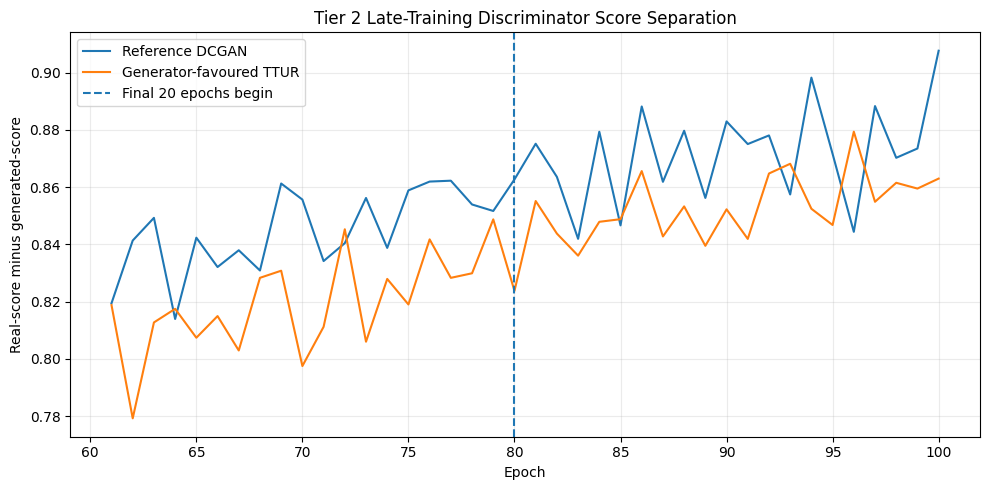

Complete trajectory plot saved: [local project directory]/grids/G07_learning_rate_ttur_tier2_trajectory_comparison.png
Late score-separation plot saved: [local project directory]/grids/G07_learning_rate_ttur_tier2_late_score_separation.png
No model is selected from training trajectories alone.
Protected test set remains unused.


In [89]:
required_lr_ttur_stability_plot_objects = [
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "LR_TTUR_TIER2_REFERENCE_RUN_ID",
    "LR_TTUR_TIER2_CANDIDATE_RUN_ID",
    "lr_ttur_tier2_history_frames",
]

missing_lr_ttur_stability_plot_objects = [
    name
    for name in required_lr_ttur_stability_plot_objects
    if name not in globals()
]

assert not missing_lr_ttur_stability_plot_objects, (
    "Incomplete Tier 2 stability plot setup:\n"
    + "\n".join(
        missing_lr_ttur_stability_plot_objects
    )
)


LR_TTUR_TIER2_TRAJECTORY_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "tier2_trajectory_comparison.png"
    )
)

LR_TTUR_TIER2_LATE_SEPARATION_PATH = (
    GRIDS_DIR
    / (
        "G07_learning_rate_ttur_"
        "tier2_late_score_separation.png"
    )
)


lr_ttur_tier2_history_specs = [
    {
        "label": "Reference DCGAN",
        "history_path": (
            HISTORIES_DIR
            / (
                f"{LR_TTUR_TIER2_REFERENCE_RUN_ID}"
                ".csv"
            )
        ),
    },
    {
        "label": "Generator-favoured TTUR",
        "history_path": (
            HISTORIES_DIR
            / (
                f"{LR_TTUR_TIER2_CANDIDATE_RUN_ID}"
                ".csv"
            )
        ),
    },
]


# Full 100-epoch loss and score trajectories.
plot_dcgan_history_comparison(
    history_specs=(
        lr_ttur_tier2_history_specs
    ),
    title=(
        "Tier 2 Learning-Rate and TTUR "
        "Training Trajectories"
    ),
    output_path=(
        LR_TTUR_TIER2_TRAJECTORY_PATH
    ),
)


# Epochs 61–100 discriminator score separation.
plt.figure(figsize=(10, 5))


for configuration in [
    "Reference DCGAN",
    "Generator-favoured TTUR",
]:
    history_df = (
        lr_ttur_tier2_history_frames[
            configuration
        ]
    )

    late_history_df = history_df.loc[
        history_df["epoch"] >= 61
    ].copy()

    score_separation = (
        late_history_df["real_score"]
        - late_history_df["fake_score"]
    )

    plt.plot(
        late_history_df["epoch"],
        score_separation,
        label=configuration,
    )


plt.axvline(
    80,
    linestyle="--",
    label="Final 20 epochs begin",
)

plt.xlabel("Epoch")

plt.ylabel(
    "Real-score minus generated-score"
)

plt.title(
    "Tier 2 Late-Training "
    "Discriminator Score Separation"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    LR_TTUR_TIER2_LATE_SEPARATION_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Complete trajectory plot saved:",
    LR_TTUR_TIER2_TRAJECTORY_PATH,
)

print(
    "Late score-separation plot saved:",
    LR_TTUR_TIER2_LATE_SEPARATION_PATH,
)

print(
    "No model is selected from "
    "training trajectories alone."
)

print("Protected test set remains unused.")

#### Stability and Compute Finding

Both configurations completed the full 100-epoch budget without non-finite values, abrupt collapse or an obvious late-training failure. Their trajectories follow the same broad adversarial pattern: discriminator loss decreases, generator loss rises, real-image scores remain high and generated-image scores fall as training progresses.

The generator-favoured TTUR recipe weakened the discriminator as intended. Across the final 20 epochs, its mean score separation was `0.8539`, compared with `0.8720` for the reference. Its discriminator loss was correspondingly slightly higher (`0.1130` versus `0.1044`), while its generator loss was lower (`4.1193` versus `4.6590`).

The candidate also produced slightly less variable late-training losses:

- generator-loss standard deviation: `0.1128` versus `0.1529`;
- discriminator-loss standard deviation: `0.0155` versus `0.0217`.

The full trajectories support this result. The candidate generally maintains lower discriminator confidence on real images and higher discriminator scores for generated images, particularly during early and middle training. Its late score-separation curve also remains below the reference for most epochs, although the two curves occasionally overlap.

However, both models still become more discriminator-dominant late in training. Score separation increased from epochs 61–80 to epochs 81–100 for both configurations:

- reference: `0.8453` to `0.8720`;
- generator-favoured TTUR: `0.8196` to `0.8539`.

Therefore, halving the discriminator learning rate reduced the imbalance but did not reverse the overall late-training trend. Neither configuration shows a decisive stability failure, and the candidate's smoother trajectory should be treated as supportive rather than conclusive evidence.

The architectures, parameter counts and update exposure were identical. Both models used `1,085,187` generator parameters, `664,129` discriminator parameters and `78,200` updates per network. The candidate recorded `21.24` minutes of training time compared with `19.47` minutes for the reference, a difference of approximately `1.77` minutes. Because the computational graph and update count were unchanged, this timing difference is not evidence that TTUR is inherently more computationally expensive and may reflect ordinary runtime variation.

Overall, stability evidence weakly favours the generator-favoured TTUR candidate because it reduced discriminator dominance and late-training variability without introducing collapse. The advantage is modest, however, and losses or discriminator scores do not establish superior generated-image quality by themselves.

The learning-rate and TTUR decision must now be made from the complete Tier 2 evidence package rather than from this diagnostic alone.

### 10.13 Final Learning-Rate and TTUR Evidence Table and Decision

The complete Tier 2 evidence is consolidated before deciding whether the generator-favoured TTUR recipe should be rejected, adopted, or advanced to seed-123 confirmation.

The decision does not count the number of favourable metrics mechanically. Different evidence sources have different roles:

- repeated FID is the primary quantitative distribution comparison;
- manual scoring provides recognisability evidence at limited resolution;
- classifier coverage and low-level descriptors provide supporting distribution evidence;
- diversity and duplicate checks act as safeguards against mode collapse;
- losses and discriminator scores diagnose adversarial balance rather than image quality;
- runtime and model size capture practical cost.

A seed-42 advantage is not treated as a confirmed retained setting. Confirmation is triggered only if the complete evidence provides a credible adoption path worth testing independently.

In [90]:
required_lr_ttur_final_evidence_objects = [
    "LR_TTUR_TIER2_REFERENCE_RUN_ID",
    "LR_TTUR_TIER2_CANDIDATE_RUN_ID",
    "LR_TTUR_TIER2_REFERENCE_EPOCH",
    "LR_TTUR_TIER2_CANDIDATE_EPOCH",
    "LR_TTUR_TIER2_REFERENCE_FID",
    "LR_TTUR_TIER2_CANDIDATE_FID",
    "LR_TTUR_PRACTICAL_FID_MARGIN",
    "lr_ttur_repeated_fid_summary_df",
    "lr_ttur_repeated_fid_improvement",
    "LR_TTUR_REFERENCE_MANUAL_COUNTS",
    "LR_TTUR_CANDIDATE_MANUAL_COUNTS",
    "LR_TTUR_MANUAL_RESOLUTION",
    "candidate_clear_difference",
    "candidate_nonsense_difference",
    "lr_ttur_reference_js",
    "lr_ttur_candidate_js",
    "lr_ttur_descriptor_closeness_df",
    "lr_ttur_diversity_summary_df",
    "lr_ttur_exact_duplicate_df",
    "lr_ttur_stability_compute_df",
    "HISTORIES_DIR",
]

missing_lr_ttur_final_evidence_objects = [
    name
    for name in required_lr_ttur_final_evidence_objects
    if name not in globals()
]

assert not missing_lr_ttur_final_evidence_objects, (
    "Incomplete final TTUR evidence setup:\n"
    + "\n".join(
        missing_lr_ttur_final_evidence_objects
    )
)


reference_repeat_row = (
    lr_ttur_repeated_fid_summary_df.loc[
        lr_ttur_repeated_fid_summary_df[
            "Configuration"
        ] == "Reference"
    ].iloc[0]
)

candidate_repeat_row = (
    lr_ttur_repeated_fid_summary_df.loc[
        lr_ttur_repeated_fid_summary_df[
            "Configuration"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


reference_coverage_row = (
    lr_ttur_coverage_summary_df.loc[
        lr_ttur_coverage_summary_df[
            "Model"
        ] == "Reference DCGAN"
    ].iloc[0]
)

candidate_coverage_row = (
    lr_ttur_coverage_summary_df.loc[
        lr_ttur_coverage_summary_df[
            "Model"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


reference_diversity_row = (
    lr_ttur_diversity_summary_df.loc[
        lr_ttur_diversity_summary_df[
            "Configuration"
        ] == "Reference DCGAN"
    ].iloc[0]
)

candidate_diversity_row = (
    lr_ttur_diversity_summary_df.loc[
        lr_ttur_diversity_summary_df[
            "Configuration"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


reference_duplicate_row = (
    lr_ttur_exact_duplicate_df.loc[
        lr_ttur_exact_duplicate_df[
            "Configuration"
        ] == "Reference DCGAN"
    ].iloc[0]
)

candidate_duplicate_row = (
    lr_ttur_exact_duplicate_df.loc[
        lr_ttur_exact_duplicate_df[
            "Configuration"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


reference_stability_row = (
    lr_ttur_stability_compute_df.loc[
        lr_ttur_stability_compute_df[
            "Configuration"
        ] == "Reference DCGAN"
    ].iloc[0]
)

candidate_stability_row = (
    lr_ttur_stability_compute_df.loc[
        lr_ttur_stability_compute_df[
            "Configuration"
        ] == "Generator-favoured TTUR"
    ].iloc[0]
)


candidate_descriptor_mean_wins = int(
    (
        lr_ttur_descriptor_closeness_df[
            "Mean closer to real"
        ]
        == "Generator-favoured TTUR"
    ).sum()
)

reference_descriptor_mean_wins = int(
    (
        lr_ttur_descriptor_closeness_df[
            "Mean closer to real"
        ]
        == "Reference DCGAN"
    ).sum()
)

candidate_descriptor_variation_wins = int(
    (
        lr_ttur_descriptor_closeness_df[
            "Variation closer to real"
        ]
        == "Generator-favoured TTUR"
    ).sum()
)

reference_descriptor_variation_wins = int(
    (
        lr_ttur_descriptor_closeness_df[
            "Variation closer to real"
        ]
        == "Reference DCGAN"
    ).sum()
)


runtime_difference_minutes = float(
    candidate_stability_row[
        "Training time minutes"
    ]
    - reference_stability_row[
        "Training time minutes"
    ]
)

runtime_difference_percent = float(
    runtime_difference_minutes
    / reference_stability_row[
        "Training time minutes"
    ]
    * 100.0
)


lr_ttur_final_evidence_df = pd.DataFrame(
    [
        {
            "Evidence": "Selected checkpoint",
            "Reference DCGAN": (
                f"Epoch "
                f"{LR_TTUR_TIER2_REFERENCE_EPOCH}"
            ),
            "Generator-favoured TTUR": (
                f"Epoch "
                f"{LR_TTUR_TIER2_CANDIDATE_EPOCH}"
            ),
            "Comparison": (
                "Both selected at epoch 100"
            ),
            "Evidence direction": "Tie",
            "Decision role": (
                "Confirms matched checkpoint timing"
            ),
        },
        {
            "Evidence": "Milestone FID",
            "Reference DCGAN": (
                f"{LR_TTUR_TIER2_REFERENCE_FID:.4f}"
            ),
            "Generator-favoured TTUR": (
                f"{LR_TTUR_TIER2_CANDIDATE_FID:.4f}"
            ),
            "Comparison": (
                "Candidate lower by "
                f"{(
                    LR_TTUR_TIER2_REFERENCE_FID
                    - LR_TTUR_TIER2_CANDIDATE_FID
                ):.4f}"
            ),
            "Evidence direction": (
                "Candidate, below practical margin"
            ),
            "Decision role": (
                "Screening evidence only"
            ),
        },
        {
            "Evidence": "Repeated FID",
            "Reference DCGAN": (
                f"{reference_repeat_row[
                    'Repeated FID mean'
                ]:.4f} ± "
                f"{reference_repeat_row[
                    'Repeated FID SD'
                ]:.4f}"
            ),
            "Generator-favoured TTUR": (
                f"{candidate_repeat_row[
                    'Repeated FID mean'
                ]:.4f} ± "
                f"{candidate_repeat_row[
                    'Repeated FID SD'
                ]:.4f}"
            ),
            "Comparison": (
                "Candidate lower by "
                f"{lr_ttur_repeated_fid_improvement:.4f}; "
                f"margin = "
                f"{LR_TTUR_PRACTICAL_FID_MARGIN:.1f}"
            ),
            "Evidence direction": (
                "Candidate, practical tie"
            ),
            "Decision role": (
                "Primary quantitative evidence, "
                "not independently decisive"
            ),
        },
        {
            "Evidence": "Manual quality",
            "Reference DCGAN": (
                f"{LR_TTUR_REFERENCE_MANUAL_COUNTS['Clear']} "
                "Clear / "
                f"{LR_TTUR_REFERENCE_MANUAL_COUNTS['Marginal']} "
                "Marginal / "
                f"{LR_TTUR_REFERENCE_MANUAL_COUNTS['Nonsense']} "
                "Nonsense"
            ),
            "Generator-favoured TTUR": (
                f"{LR_TTUR_CANDIDATE_MANUAL_COUNTS['Clear']} "
                "Clear / "
                f"{LR_TTUR_CANDIDATE_MANUAL_COUNTS['Marginal']} "
                "Marginal / "
                f"{LR_TTUR_CANDIDATE_MANUAL_COUNTS['Nonsense']} "
                "Nonsense"
            ),
            "Comparison": (
                f"{candidate_clear_difference:+d} Clear, "
                f"{candidate_nonsense_difference:+d} "
                "Nonsense; "
                f"resolution ≈ "
                f"{LR_TTUR_MANUAL_RESOLUTION}"
            ),
            "Evidence direction": (
                "Candidate, below manual resolution"
            ),
            "Decision role": (
                "Supportive recognisability evidence"
            ),
        },
        {
            "Evidence": "Classifier coverage",
            "Reference DCGAN": (
                f"{int(reference_coverage_row[
                    'Represented classes'
                ])}/10 classes; "
                f"JS = {lr_ttur_reference_js:.4f}"
            ),
            "Generator-favoured TTUR": (
                f"{int(candidate_coverage_row[
                    'Represented classes'
                ])}/10 classes; "
                f"JS = {lr_ttur_candidate_js:.4f}"
            ),
            "Comparison": (
                "Candidate JS lower by "
                f"{(
                    lr_ttur_reference_js
                    - lr_ttur_candidate_js
                ):.4f}"
            ),
            "Evidence direction": (
                "Candidate, weak advantage"
            ),
            "Decision role": (
                "Supporting coverage evidence"
            ),
        },
        {
            "Evidence": "Descriptor means",
            "Reference DCGAN": (
                f"Closer on "
                f"{reference_descriptor_mean_wins}/7"
            ),
            "Generator-favoured TTUR": (
                f"Closer on "
                f"{candidate_descriptor_mean_wins}/7"
            ),
            "Comparison": (
                "Candidate closer for brightness, "
                "RGB balance and edge strength"
            ),
            "Evidence direction": (
                "Candidate"
            ),
            "Decision role": (
                "Supporting low-level distribution evidence"
            ),
        },
        {
            "Evidence": "Descriptor variation",
            "Reference DCGAN": (
                f"Closer on "
                f"{reference_descriptor_variation_wins}/7"
            ),
            "Generator-favoured TTUR": (
                f"Closer on "
                f"{candidate_descriptor_variation_wins}/7"
            ),
            "Comparison": (
                "Small mixed advantage"
            ),
            "Evidence direction": (
                "Candidate, weak advantage"
            ),
            "Decision role": (
                "Supporting variation evidence"
            ),
        },
        {
            "Evidence": "Feature-space diversity",
            "Reference DCGAN": (
                f"{reference_diversity_row[
                    'diversity_ratio_mean'
                ]:.4f} ± "
                f"{reference_diversity_row[
                    'diversity_ratio_sd'
                ]:.4f}"
            ),
            "Generator-favoured TTUR": (
                f"{candidate_diversity_row[
                    'diversity_ratio_mean'
                ]:.4f} ± "
                f"{candidate_diversity_row[
                    'diversity_ratio_sd'
                ]:.4f}"
            ),
            "Comparison": (
                "Reference marginally closer to "
                "real ratio 1.0"
            ),
            "Evidence direction": (
                "Reference, negligible advantage"
            ),
            "Decision role": (
                "Diversity safeguard passed by both"
            ),
        },
        {
            "Evidence": "Repetition",
            "Reference DCGAN": (
                f"{reference_diversity_row[
                    'near_duplicate_rate_mean'
                ]:.2f}% near; "
                f"{int(reference_duplicate_row[
                    'Exact duplicates'
                ])} exact"
            ),
            "Generator-favoured TTUR": (
                f"{candidate_diversity_row[
                    'near_duplicate_rate_mean'
                ]:.2f}% near; "
                f"{int(candidate_duplicate_row[
                    'Exact duplicates'
                ])} exact"
            ),
            "Comparison": (
                "No detected repetition for either model"
            ),
            "Evidence direction": "Tie",
            "Decision role": (
                "Mode-collapse safeguard passed"
            ),
        },
        {
            "Evidence": "Late-training balance",
            "Reference DCGAN": (
                "Score separation = "
                f"{reference_stability_row[
                    'Final-20 score separation'
                ]:.4f}; "
                "G-loss SD = "
                f"{reference_stability_row[
                    'Final-20 G loss SD'
                ]:.4f}"
            ),
            "Generator-favoured TTUR": (
                "Score separation = "
                f"{candidate_stability_row[
                    'Final-20 score separation'
                ]:.4f}; "
                "G-loss SD = "
                f"{candidate_stability_row[
                    'Final-20 G loss SD'
                ]:.4f}"
            ),
            "Comparison": (
                "Candidate reduces discriminator "
                "dominance and late loss variation"
            ),
            "Evidence direction": (
                "Candidate, modest diagnostic advantage"
            ),
            "Decision role": (
                "Balance and stability diagnostic only"
            ),
        },
        {
            "Evidence": "Training compute",
            "Reference DCGAN": (
                f"{reference_stability_row[
                    'Training time minutes'
                ]:.2f} minutes"
            ),
            "Generator-favoured TTUR": (
                f"{candidate_stability_row[
                    'Training time minutes'
                ]:.2f} minutes"
            ),
            "Comparison": (
                f"Candidate +{runtime_difference_minutes:.2f} "
                "minutes "
                f"(+{runtime_difference_percent:.1f}%)"
            ),
            "Evidence direction": (
                "Reference, small runtime advantage"
            ),
            "Decision role": (
                "Same architecture and update exposure; "
                "timing difference is secondary"
            ),
        },
    ]
)


LR_TTUR_FINAL_EVIDENCE_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "tier2_final_evidence.csv"
    )
)

lr_ttur_final_evidence_df.to_csv(
    LR_TTUR_FINAL_EVIDENCE_PATH,
    index=False,
)


display(
    lr_ttur_final_evidence_df
)

print(
    "Final Tier 2 evidence table saved:",
    LR_TTUR_FINAL_EVIDENCE_PATH,
)

print(
    "This table consolidates evidence; "
    "it does not select the model automatically."
)

print("Protected test set remains unused.")

,Evidence,Reference DCGAN,Generator-favoured TTUR,Comparison,Evidence direction,Decision role
0,Selected checkpoint,Epoch 100,Epoch 100,Both selected at epoch 100,Tie,Confirms matched checkpoint timing
1,Milestone FID,36.7759,35.7858,Candidate lower by 0.9902,"Candidate, below practical margin",Screening evidence only
2,Repeated FID,37.0260 ± 0.3139,35.7626 ± 0.3984,Candidate lower by 1.2635; margin = 2.0,"Candidate, practical tie","Primary quantitative evidence, not independent..."
3,Manual quality,9 Clear / 75 Marginal / 16 Nonsense,17 Clear / 71 Marginal / 12 Nonsense,"+8 Clear, -4 Nonsense; resolution ≈ 13","Candidate, below manual resolution",Supportive recognisability evidence
4,Classifier coverage,10/10 classes; JS = 0.0134,10/10 classes; JS = 0.0121,Candidate JS lower by 0.0013,"Candidate, weak advantage",Supporting coverage evidence
5,Descriptor means,Closer on 2/7,Closer on 5/7,"Candidate closer for brightness, RGB balance a...",Candidate,Supporting low-level distribution evidence
6,Descriptor variation,Closer on 3/7,Closer on 4/7,Small mixed advantage,"Candidate, weak advantage",Supporting variation evidence
7,Feature-space diversity,0.9340 ± 0.0077,0.9325 ± 0.0063,Reference marginally closer to real ratio 1.0,"Reference, negligible advantage",Diversity safeguard passed by both
8,Repetition,0.00% near; 0 exact,0.00% near; 0 exact,No detected repetition for either model,Tie,Mode-collapse safeguard passed
9,Late-training balance,Score separation = 0.8720; G-loss SD = 0.1529,Score separation = 0.8539; G-loss SD = 0.1128,Candidate reduces discriminator dominance and ...,"Candidate, modest diagnostic advantage",Balance and stability diagnostic only


Final Tier 2 evidence table saved: [local project directory]/histories/learning_rate_ttur_tier2_final_evidence.csv
This table consolidates evidence; it does not select the model automatically.
Protected test set remains unused.


#### Final Tier 2 Decision

The generator-favoured TTUR recipe is **provisionally advanced to seed-123 confirmation**, but it is not yet adopted as the carried configuration.

The repeated-FID improvement of `1.2635` remains inside the predeclared `2.0` practical tie margin. The manual improvement of `+8` Clear images and `-4` Nonsense images is also below the approximate 13-image resolution threshold. Neither result independently justifies replacing the reference.

However, the candidate has now established a coherent multi-evidence adoption path:

- lower FID under all three repeated sampling seeds;
- more Clear and fewer Nonsense images;
- slightly closer classifier-predicted class coverage;
- substantially better brightness, RGB-mean and edge-strength alignment;
- modestly reduced discriminator dominance and late-training loss variability;
- no exact duplicates, near duplicates or meaningful diversity degradation.

The reference retains only small advantages in feature-space diversity, selected contrast and saturation descriptors, and recorded runtime. These do not outweigh the candidate evidence strongly enough to reject it, but the candidate evidence is also not strong enough for immediate adoption from one training seed.

Because the TTUR setting would affect all later augmentation and final-model experiments, and because the seed-42 comparison is close but consistently candidate-leaning across several independent evidence sources, one fresh seed-123 confirmation is justified.

The provisional confirmation target is therefore:

```text
generator learning rate:     2e-4
discriminator learning rate: 1e-4
training seed:               123
training budget:             100 epochs
update ratio:                1D : 1G
architecture:                unchanged selected DCGAN
latent dimension:            100
batch size:                  64
```

This is not a fifth TTUR recipe. It is an independent confirmation of the exact Tier 2 candidate.

If seed `123` does not reproduce the candidate's claimed quality and balance advantage, the original equal-rate `2e-4` / `2e-4` reference will be retained and the TTUR family will close.

In [91]:
LR_TTUR_PROVISIONAL_DECISION = (
    "Advance generator-favoured TTUR "
    "to seed-123 confirmation"
)

LR_TTUR_CONFIRMATION_TRIGGERED = True

LR_TTUR_CONFIRMATION_RUN_ID = (
    "G07_recipe_generatorfavoured_seed123"
)

LR_TTUR_CONFIRMATION_TRAINING_SEED = 123

LR_TTUR_CONFIRMATION_GENERATOR_LR = (
    LR_TTUR_GENERATOR_FAVOURED_GENERATOR_LR
)

LR_TTUR_CONFIRMATION_DISCRIMINATOR_LR = (
    LR_TTUR_GENERATOR_FAVOURED_DISCRIMINATOR_LR
)


lr_ttur_provisional_decision_df = pd.DataFrame(
    [
        {
            "Family": "Learning rate and TTUR",
            "Provisional decision": (
                LR_TTUR_PROVISIONAL_DECISION
            ),
            "Candidate run ID": (
                LR_TTUR_TIER2_CANDIDATE_RUN_ID
            ),
            "Confirmation triggered": (
                LR_TTUR_CONFIRMATION_TRIGGERED
            ),
            "Confirmation run ID": (
                LR_TTUR_CONFIRMATION_RUN_ID
            ),
            "Confirmation seed": (
                LR_TTUR_CONFIRMATION_TRAINING_SEED
            ),
            "Generator learning rate": (
                LR_TTUR_CONFIRMATION_GENERATOR_LR
            ),
            "Discriminator learning rate": (
                LR_TTUR_CONFIRMATION_DISCRIMINATOR_LR
            ),
            "Final adoption status": (
                "Pending seed-123 confirmation"
            ),
        }
    ]
)


LR_TTUR_PROVISIONAL_DECISION_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "provisional_decision.csv"
    )
)

lr_ttur_provisional_decision_df.to_csv(
    LR_TTUR_PROVISIONAL_DECISION_PATH,
    index=False,
)

display(
    lr_ttur_provisional_decision_df
)

print(
    "Provisional TTUR decision saved:",
    LR_TTUR_PROVISIONAL_DECISION_PATH,
)

print(
    "No TTUR recipe has been finally adopted yet."
)

print("Protected test set remains unused.")

,Family,Provisional decision,Candidate run ID,Confirmation triggered,Confirmation run ID,Confirmation seed,Generator learning rate,Discriminator learning rate,Final adoption status
0,Learning rate and TTUR,Advance generator-favoured TTUR to seed-123 co...,G07_recipe_generatorfavoured_seed42,True,G07_recipe_generatorfavoured_seed123,123,0.0002,0.0001,Pending seed-123 confirmation


Provisional TTUR decision saved: [local project directory]/histories/learning_rate_ttur_provisional_decision.csv
No TTUR recipe has been finally adopted yet.
Protected test set remains unused.


### 10.14 Seed-123 Generator-Favoured TTUR Confirmation

The generator-favoured TTUR recipe now receives one independent training-seed confirmation.

The confirmation changes only the training seed from `42` to `123`. It retains:

- the original selected generator and discriminator architectures;
- latent dimension `100`;
- `Conv2DTranspose` upsampling;
- batch size `64`;
- generator learning rate `2 × 10⁻⁴`;
- discriminator learning rate `1 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- binary cross-entropy;
- one discriminator update per generator update;
- no augmentation;
- the full 100-epoch budget;
- progression grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100.

Fresh generator, discriminator and optimiser states are created. No weights or optimiser states are transferred from the seed-42 candidate.

After training, the four milestone checkpoints will be evaluated using the unchanged development-FID protocol. Only the confirmation evidence needed for the final TTUR decision will be repeated.

No seed `456` or `789` will be added for this intermediate family, and the protected CIFAR-10 test set remains unused.

In [45]:
required_lr_ttur_confirmation_objects = [
    "SECONDARY_SEED",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "CURRENT_UPSAMPLING",
    "CURRENT_AUGMENTATION",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "build_dcgan_generator",
    "build_dcgan_discriminator",
    "run_dcgan_family",
    "REQUIRED_DCGAN_FAMILY_CONFIG_KEYS",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_confirmation_objects = [
    name
    for name in required_lr_ttur_confirmation_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_objects, (
    "Incomplete TTUR confirmation setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_objects
    )
)


LR_TTUR_CONFIRMATION_RUN_ID = (
    "G07_recipe_generatorfavoured_seed123"
)

LR_TTUR_CONFIRMATION_LABEL = (
    "DCGAN Generator-Favoured TTUR, Seed 123"
)

LR_TTUR_CONFIRMATION_TRAINING_SEED = (
    SECONDARY_SEED
)

LR_TTUR_CONFIRMATION_GENERATOR_LR = 2e-4
LR_TTUR_CONFIRMATION_DISCRIMINATOR_LR = 1e-4

LR_TTUR_CONFIRMATION_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL = 10

LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)


assert LR_TTUR_CONFIRMATION_TRAINING_SEED == 123
assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CURRENT_EPOCHS == 100

assert CURRENT_UPSAMPLING == "Conv2DTranspose"
assert CURRENT_AUGMENTATION == "None"
assert CURRENT_UPDATE_RATIO == "1D:1G"

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert (
    LR_TTUR_CONFIRMATION_GENERATOR_LR,
    LR_TTUR_CONFIRMATION_DISCRIMINATOR_LR,
) == (
    2e-4,
    1e-4,
)

assert LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)


LR_TTUR_CONFIRMATION_CONFIGURATIONS = [
    {
        "run_id": (
            LR_TTUR_CONFIRMATION_RUN_ID
        ),
        "configuration_label": (
            LR_TTUR_CONFIRMATION_LABEL
        ),
        "main_change": (
            "Independent seed-123 confirmation "
            "of generator learning rate 2e-4 "
            "and discriminator learning rate 1e-4"
        ),
        "training_seed": (
            LR_TTUR_CONFIRMATION_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            build_dcgan_discriminator
        ),
        "generator_learning_rate": (
            LR_TTUR_CONFIRMATION_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            LR_TTUR_CONFIRMATION_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]


assert len(
    LR_TTUR_CONFIRMATION_CONFIGURATIONS
) == 1

confirmation_configuration = (
    LR_TTUR_CONFIRMATION_CONFIGURATIONS[0]
)

missing_configuration_keys = [
    key
    for key in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
    if key not in confirmation_configuration
]

assert not missing_configuration_keys, (
    "Confirmation configuration is missing:\n"
    + "\n".join(
        missing_configuration_keys
    )
)

assert (
    confirmation_configuration[
        "generator_builder"
    ]
    is build_dcgan_generator
)

assert (
    confirmation_configuration[
        "discriminator_builder"
    ]
    is build_dcgan_discriminator
)

assert (
    confirmation_configuration[
        "training_seed"
    ]
    == 123
)

print(
    "TTUR seed-123 confirmation "
    "configuration declared."
)

print(
    "Run ID:",
    LR_TTUR_CONFIRMATION_RUN_ID,
)

print(
    "Only the training seed differs "
    "from the seed-42 candidate."
)

TTUR seed-123 confirmation configuration declared.
Run ID: G07_recipe_generatorfavoured_seed123
Only the training seed differs from the seed-42 candidate.


In [46]:
keras.backend.clear_session()

reset_run_seed(
    LR_TTUR_CONFIRMATION_TRAINING_SEED
)


lr_ttur_confirmation_probe_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_confirmation_probe_discriminator = (
    build_dcgan_discriminator()
)


assert (
    lr_ttur_confirmation_probe_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    lr_ttur_confirmation_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


lr_ttur_confirmation_probe_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=FIXED_PROGRESSION_SEED,
    )
)

lr_ttur_confirmation_probe_images = (
    lr_ttur_confirmation_probe_generator(
        lr_ttur_confirmation_probe_noise,
        training=False,
    )
)

lr_ttur_confirmation_probe_scores = (
    lr_ttur_confirmation_probe_discriminator(
        lr_ttur_confirmation_probe_images,
        training=False,
    )
)


assert lr_ttur_confirmation_probe_images.shape == (
    8,
    32,
    32,
    3,
)

assert lr_ttur_confirmation_probe_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    lr_ttur_confirmation_probe_images.numpy()
).all()

assert np.isfinite(
    lr_ttur_confirmation_probe_scores.numpy()
).all()


print(
    "Generator parameters:",
    lr_ttur_confirmation_probe_generator.count_params(),
)

print(
    "Discriminator parameters:",
    lr_ttur_confirmation_probe_discriminator.count_params(),
)

print(
    "Seed-123 architecture and output "
    "contracts validated."
)


del lr_ttur_confirmation_probe_generator
del lr_ttur_confirmation_probe_discriminator
del lr_ttur_confirmation_probe_noise
del lr_ttur_confirmation_probe_images
del lr_ttur_confirmation_probe_scores

keras.backend.clear_session()
gc.collect()

Generator parameters: 1085187
Discriminator parameters: 664129
Seed-123 architecture and output contracts validated.


0

In [47]:
keras.backend.clear_session()


lr_ttur_confirmation_training_df = (
    run_dcgan_family(
        family_name=(
            "Learning-rate and TTUR "
            "seed-123 confirmation"
        ),
        configurations=(
            LR_TTUR_CONFIRMATION_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=(
            LR_TTUR_CONFIRMATION_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)


display(
    lr_ttur_confirmation_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


print(
    "Generator-favoured TTUR seed-123 "
    "confirmation training call completed."
)

print(
    "No final TTUR adoption decision "
    "has been made."
)

print(
    "No seed 456 or 789 will be trained "
    "for this intermediate family."
)

print(
    "Protected test set remains unused."
)

Declared family: Learning-rate and TTUR seed-123 confirmation


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G07_recipe_generatorfavoured_seed123,"DCGAN Generator-Favoured TTUR, Seed 123",Independent seed-123 confirmation of generator...,123,100,64,0.0002,0.0001,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G07_recipe_generatorfavoured_seed123
Configuration: DCGAN Generator-Favoured TTUR, Seed 123
Main change: Independent seed-123 confirmation of generator learning rate 2e-4 and discriminator learning rate 1e-4
Training new run G07_recipe_generatorfavoured_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.2182 | D loss: 0.2073 | Real: 0.8458 | Fake: 0.1547 | Time: 17.9s
Epoch 002/100 | G loss: 0.6558 | D loss: 0.2320 | Real: 0.8265 | Fake: 0.1688 | Time: 12.2s
Epoch 003/100 | G loss: 0.3895 | D loss: 0.0929 | Real: 0.9273 | Fake: 0.0693 | Time: 12.1s
Epoch 004/100 | G loss: 0.7372 | D loss: 0.1581 | Real: 0.8874 | Fake: 0.1100 | Time: 12.1s
Epoch 005/100 | G loss: 1.0288 | D loss: 0.1882 | Real: 0.8686 | Fake: 0.1297 | Time: 12.1s
Epoch 006/100 | G loss: 1.2044 | D loss: 0.1523 | Real: 0.8849 | Fake: 0.1134 | Time: 12.2s
Epoch 007/100 | G loss: 1.1214 | D lo

,run_id,configuration_label,action,epochs_completed,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G07_recipe_generatorfavoured_seed123,"DCGAN Generator-Favoured TTUR, Seed 123",trained_new,100,78200,78200,1085187,664129,20.3754


Generator-favoured TTUR seed-123 confirmation training call completed.
No final TTUR adoption decision has been made.
No seed 456 or 789 will be trained for this intermediate family.
Protected test set remains unused.


#### Seed-123 Training Artifact Audit

Before checkpoint evaluation, the persisted confirmation artifacts are checked independently of the completed training call.

The audit verifies:

- a complete finite 100-row history;
- a resumable epoch-100 checkpoint;
- fixed-seed progression grids every 10 epochs;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100;
- the expected update exposure implied by 782 batches across 100 epochs.

Passing this audit confirms that the run can be evaluated or recovered after a fresh runtime without retraining.

In [51]:
required_lr_ttur_confirmation_audit_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_TARGET_EPOCHS",
    "LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS",
    "LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL",
    "CURRENT_BATCH_SIZE",
    "STANDARD_DCGAN_HISTORY_COLUMNS",
    "inspect_dcgan_training_status",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_confirmation_audit_objects = [
    name
    for name in required_lr_ttur_confirmation_audit_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_audit_objects, (
    "Incomplete confirmation artifact-audit setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_audit_objects
    )
)


LR_TTUR_CONFIRMATION_BATCHES_PER_EPOCH = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

LR_TTUR_CONFIRMATION_EXPECTED_UPDATES = (
    LR_TTUR_CONFIRMATION_BATCHES_PER_EPOCH
    * LR_TTUR_CONFIRMATION_TARGET_EPOCHS
)


assert LR_TTUR_CONFIRMATION_TARGET_EPOCHS == 100
assert CURRENT_BATCH_SIZE == 64

assert LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL == 10
assert LR_TTUR_CONFIRMATION_BATCHES_PER_EPOCH == 782
assert LR_TTUR_CONFIRMATION_EXPECTED_UPDATES == 78_200


lr_ttur_confirmation_status = (
    inspect_dcgan_training_status(
        run_id=LR_TTUR_CONFIRMATION_RUN_ID,
        target_epochs=(
            LR_TTUR_CONFIRMATION_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL
        ),
    )
)


lr_ttur_confirmation_history_path = (
    HISTORIES_DIR
    / f"{LR_TTUR_CONFIRMATION_RUN_ID}.csv"
)

assert lr_ttur_confirmation_history_path.is_file()


lr_ttur_confirmation_history_df = pd.read_csv(
    lr_ttur_confirmation_history_path
)

missing_history_columns = [
    column
    for column in STANDARD_DCGAN_HISTORY_COLUMNS
    if column
    not in lr_ttur_confirmation_history_df.columns
]

assert not missing_history_columns, (
    "Confirmation history is missing:\n"
    + "\n".join(
        missing_history_columns
    )
)


lr_ttur_confirmation_history_df = (
    lr_ttur_confirmation_history_df[
        STANDARD_DCGAN_HISTORY_COLUMNS
    ]
    .copy()
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(
    lr_ttur_confirmation_history_df
) == LR_TTUR_CONFIRMATION_TARGET_EPOCHS

assert np.array_equal(
    lr_ttur_confirmation_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        LR_TTUR_CONFIRMATION_TARGET_EPOCHS + 1,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    lr_ttur_confirmation_history_df[
        STANDARD_DCGAN_HISTORY_COLUMNS
    ].to_numpy(dtype=np.float64)
).all()


lr_ttur_confirmation_expected_grid_epochs = tuple(
    range(
        LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL,
        LR_TTUR_CONFIRMATION_TARGET_EPOCHS + 1,
        LR_TTUR_CONFIRMATION_CHECKPOINT_INTERVAL,
    )
)


lr_ttur_confirmation_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in lr_ttur_confirmation_expected_grid_epochs
}


lr_ttur_confirmation_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
}


lr_ttur_confirmation_discriminator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch
    in LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
}


for path in (
    list(
        lr_ttur_confirmation_grid_paths.values()
    )
    + list(
        lr_ttur_confirmation_generator_paths.values()
    )
    + list(
        lr_ttur_confirmation_discriminator_paths.values()
    )
):
    assert path.is_file(), (
        f"Missing confirmation artifact:\n{path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty confirmation artifact:\n{path}"
    )


latest_confirmation_checkpoint = (
    tf.train.latest_checkpoint(
        str(
            CHECKPOINTS_DIR
            / LR_TTUR_CONFIRMATION_RUN_ID
        )
    )
)

assert latest_confirmation_checkpoint is not None

assert (
    lr_ttur_confirmation_status["status"]
    == "completed"
)

assert (
    lr_ttur_confirmation_status[
        "checkpoint_epoch"
    ]
    == LR_TTUR_CONFIRMATION_TARGET_EPOCHS
)


lr_ttur_confirmation_artifact_audit_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    LR_TTUR_CONFIRMATION_RUN_ID
                ),
                "Status": (
                    lr_ttur_confirmation_status[
                        "status"
                    ]
                ),
                "History rows": len(
                    lr_ttur_confirmation_history_df
                ),
                "Checkpoint epoch": (
                    lr_ttur_confirmation_status[
                        "checkpoint_epoch"
                    ]
                ),
                "Progression grids": len(
                    lr_ttur_confirmation_grid_paths
                ),
                "Generator milestones": len(
                    lr_ttur_confirmation_generator_paths
                ),
                "Discriminator milestones": len(
                    lr_ttur_confirmation_discriminator_paths
                ),
                "Batches per epoch": (
                    LR_TTUR_CONFIRMATION_BATCHES_PER_EPOCH
                ),
                "Expected generator updates": (
                    LR_TTUR_CONFIRMATION_EXPECTED_UPDATES
                ),
                "Expected discriminator updates": (
                    LR_TTUR_CONFIRMATION_EXPECTED_UPDATES
                ),
                "Finite history": True,
                "Recorded training time minutes": (
                    lr_ttur_confirmation_history_df[
                        "epoch_time_seconds"
                    ].sum()
                    / 60.0
                ),
            }
        ]
    )
)


LR_TTUR_CONFIRMATION_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "seed123_confirmation_artifact_audit.csv"
    )
)

lr_ttur_confirmation_artifact_audit_df.to_csv(
    LR_TTUR_CONFIRMATION_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    lr_ttur_confirmation_artifact_audit_df.round(4)
)


print(
    "Seed-123 confirmation artifact audit passed."
)

print(
    "Latest checkpoint:",
    latest_confirmation_checkpoint,
)

print(
    "Artifact audit saved:",
    LR_TTUR_CONFIRMATION_ARTIFACT_AUDIT_PATH,
)

print(
    "Checkpoint selection has not yet been performed."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Expected generator updates,Expected discriminator updates,Finite history,Recorded training time minutes
0,G07_recipe_generatorfavoured_seed123,completed,100,100,10,4,4,782,78200,78200,True,20.3754


Seed-123 confirmation artifact audit passed.
Latest checkpoint: [local project directory]/checkpoints/G07_recipe_generatorfavoured_seed123/ckpt-100
Artifact audit saved: [local project directory]/histories/learning_rate_ttur_seed123_confirmation_artifact_audit.csv
Checkpoint selection has not yet been performed.
Protected test set remains unused.


#### Seed-123 Milestone Development FID

The completed seed-123 confirmation generator is evaluated at epochs 50, 70, 90 and 100.

Each checkpoint generates the same number of images using the fixed milestone-selection seed `1001`. The generated images are compared against the unchanged CIFAR-10 training-reference feature statistics.

This stage selects a provisional checkpoint within the seed-123 run. It does not yet determine whether the TTUR recipe is adopted.

In [53]:
required_lr_ttur_confirmation_fid_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_TRAINING_SEED",
    "LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "FID_FEATURE_DIM",
    "MILESTONE_FID_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_features",
    "real_fid_mean",
    "real_fid_covariance",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_lr_ttur_confirmation_fid_objects = [
    name
    for name in required_lr_ttur_confirmation_fid_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_fid_objects, (
    "Incomplete seed-123 milestone FID setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_fid_objects
    )
)


assert LR_TTUR_CONFIRMATION_TRAINING_SEED == 123

assert LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert CURRENT_LATENT_DIM == 100
assert FID_SAMPLE_COUNT == 5_000
assert FID_FEATURE_DIM == 2_048
assert MILESTONE_FID_SEED == 1_001

assert real_fid_features.shape == (
    50_000,
    FID_FEATURE_DIM,
)

assert real_fid_mean.shape == (
    FID_FEATURE_DIM,
)

assert real_fid_covariance.shape == (
    FID_FEATURE_DIM,
    FID_FEATURE_DIM,
)

assert np.isfinite(
    real_fid_features
).all()

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()

assert fid_feature_extractor.trainable is False


LR_TTUR_CONFIRMATION_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        "milestone_fid.csv"
    )
)

confirmation_fid_columns = [
    "run_id",
    "training_seed",
    "epoch",
    "fid_seed",
    "sample_count",
    "fid",
]


if LR_TTUR_CONFIRMATION_MILESTONE_FID_PATH.is_file():
    lr_ttur_confirmation_milestone_fid_df = (
        pd.read_csv(
            LR_TTUR_CONFIRMATION_MILESTONE_FID_PATH
        )
    )

    missing_confirmation_fid_columns = [
        column
        for column in confirmation_fid_columns
        if column
        not in (
            lr_ttur_confirmation_milestone_fid_df
            .columns
        )
    ]

    assert not missing_confirmation_fid_columns, (
        "Saved confirmation milestone FID file "
        "is missing:\n"
        + "\n".join(
            missing_confirmation_fid_columns
        )
    )

    lr_ttur_confirmation_milestone_fid_df = (
        lr_ttur_confirmation_milestone_fid_df[
            confirmation_fid_columns
        ].copy()
    )

else:
    lr_ttur_confirmation_milestone_fid_df = (
        pd.DataFrame(
            columns=confirmation_fid_columns
        )
    )


lr_ttur_confirmation_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
}


for epoch, weights_path in (
    lr_ttur_confirmation_generator_paths.items()
):
    assert weights_path.is_file(), (
        "Missing confirmation generator weights:\n"
        f"{weights_path}"
    )

    assert weights_path.stat().st_size > 0


tf.keras.backend.clear_session()

lr_ttur_confirmation_eval_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

assert (
    lr_ttur_confirmation_eval_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


for epoch in (
    LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
):
    existing_row = (
        lr_ttur_confirmation_milestone_fid_df.loc[
            (
                lr_ttur_confirmation_milestone_fid_df[
                    "run_id"
                ].astype(str)
                == LR_TTUR_CONFIRMATION_RUN_ID
            )
            & (
                pd.to_numeric(
                    lr_ttur_confirmation_milestone_fid_df[
                        "epoch"
                    ],
                    errors="coerce",
                )
                == epoch
            )
            & (
                pd.to_numeric(
                    lr_ttur_confirmation_milestone_fid_df[
                        "fid_seed"
                    ],
                    errors="coerce",
                )
                == MILESTONE_FID_SEED
            )
            & (
                pd.to_numeric(
                    lr_ttur_confirmation_milestone_fid_df[
                        "sample_count"
                    ],
                    errors="coerce",
                )
                == FID_SAMPLE_COUNT
            )
        ]
    )


    if len(existing_row) == 1:
        fid_value = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already saved: "
            f"FID {fid_value:.4f}"
        )

        continue


    weights_path = (
        lr_ttur_confirmation_generator_paths[
            epoch
        ]
    )

    lr_ttur_confirmation_eval_generator.load_weights(
        weights_path
    )


    generated_images = generate_images_uint8(
        generator=(
            lr_ttur_confirmation_eval_generator
        ),
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=MILESTONE_FID_SEED,
    )

    assert generated_images.shape == (
        FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8


    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    assert generated_features.shape == (
        FID_SAMPLE_COUNT,
        FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    assert np.isfinite(fid_value)


    new_row = pd.DataFrame(
        [
            {
                "run_id": (
                    LR_TTUR_CONFIRMATION_RUN_ID
                ),
                "training_seed": (
                    LR_TTUR_CONFIRMATION_TRAINING_SEED
                ),
                "epoch": int(epoch),
                "fid_seed": int(
                    MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        ]
    )


    lr_ttur_confirmation_milestone_fid_df = (
        lr_ttur_confirmation_milestone_fid_df.loc[
            ~(
                (
                    lr_ttur_confirmation_milestone_fid_df[
                        "run_id"
                    ].astype(str)
                    == LR_TTUR_CONFIRMATION_RUN_ID
                )
                & (
                    pd.to_numeric(
                        lr_ttur_confirmation_milestone_fid_df[
                            "epoch"
                        ],
                        errors="coerce",
                    )
                    == epoch
                )
            )
        ]
    )


    lr_ttur_confirmation_milestone_fid_df = (
        pd.concat(
            [
                lr_ttur_confirmation_milestone_fid_df,
                new_row,
            ],
            ignore_index=True,
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    lr_ttur_confirmation_milestone_fid_df.to_csv(
        LR_TTUR_CONFIRMATION_MILESTONE_FID_PATH,
        index=False,
    )


    print(
        f"Epoch {epoch:03d} development FID: "
        f"{fid_value:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del lr_ttur_confirmation_eval_generator

tf.keras.backend.clear_session()
gc.collect()


lr_ttur_confirmation_milestone_fid_df = (
    lr_ttur_confirmation_milestone_fid_df
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(
    lr_ttur_confirmation_milestone_fid_df
) == 4

assert set(
    lr_ttur_confirmation_milestone_fid_df[
        "epoch"
    ].astype(int)
) == {
    50,
    70,
    90,
    100,
}

assert np.isfinite(
    lr_ttur_confirmation_milestone_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


lr_ttur_confirmation_lowest_fid_row = (
    lr_ttur_confirmation_milestone_fid_df
    .sort_values(
        [
            "fid",
            "epoch",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .iloc[0]
)


LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH = int(
    lr_ttur_confirmation_lowest_fid_row[
        "epoch"
    ]
)

LR_TTUR_CONFIRMATION_PROVISIONAL_FID = float(
    lr_ttur_confirmation_lowest_fid_row[
        "fid"
    ]
)


display(
    lr_ttur_confirmation_milestone_fid_df[
        [
            "epoch",
            "fid_seed",
            "sample_count",
            "fid",
        ]
    ].round(4)
)


print(
    "Provisional lowest-FID epoch:",
    LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH,
)

print(
    "Provisional lowest milestone FID:",
    f"{LR_TTUR_CONFIRMATION_PROVISIONAL_FID:.4f}",
)

print(
    "Milestone FID results saved:",
    LR_TTUR_CONFIRMATION_MILESTONE_FID_PATH,
)

print(
    "Inspect the selected epoch's saved grid "
    "and trajectory before locking the checkpoint."
)

print(
    "No final TTUR adoption decision "
    "has been made."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3967/3673504410.py:346: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


Epoch 050 development FID: 42.8793


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 39.8909


...

Epoch 090 development FID: 38.9529


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 36.9352


,epoch,fid_seed,sample_count,fid
0,50,1001,5000,42.8793
1,70,1001,5000,39.8909
2,90,1001,5000,38.9529
3,100,1001,5000,36.9352


Provisional lowest-FID epoch: 100
Provisional lowest milestone FID: 36.9352
Milestone FID results saved: [local project directory]/histories/G07_recipe_generatorfavoured_seed123_milestone_fid.csv
Inspect the selected epoch's saved grid and trajectory before locking the checkpoint.
No final TTUR adoption decision has been made.
Protected test set remains unused.


#### Seed-123 Checkpoint Inspection

Epoch 100 currently has the lowest milestone development FID.

Before locking this checkpoint, the fixed-seed grids from epochs 50, 70, 90 and 100 are reviewed together with the complete training trajectory. This checks whether the numerical FID improvement is accompanied by acceptable visual progression and whether the final checkpoint shows collapse, repetition or abrupt instability.

Losses and discriminator scores are used only as adversarial-balance diagnostics. They do not directly measure image quality.

In [55]:
required_lr_ttur_confirmation_inspection_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS",
    "LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH",
    "lr_ttur_confirmation_milestone_fid_df",
    "GRIDS_DIR",
]

missing_lr_ttur_confirmation_inspection_objects = [
    name
    for name in required_lr_ttur_confirmation_inspection_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_inspection_objects, (
    "Incomplete seed-123 checkpoint-inspection setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_inspection_objects
    )
)


assert LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH == 100

assert LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)


lr_ttur_confirmation_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS
}


for grid_path in (
    lr_ttur_confirmation_grid_paths.values()
):
    assert grid_path.is_file(), (
        f"Missing milestone grid:\n{grid_path}"
    )


lr_ttur_confirmation_fid_by_epoch = (
    lr_ttur_confirmation_milestone_fid_df
    .set_index("epoch")["fid"]
    .astype(float)
    .to_dict()
)


LR_TTUR_CONFIRMATION_MILESTONE_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        "milestone_progression.png"
    )
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14),
)


for axis, epoch in zip(
    axes.flat,
    LR_TTUR_CONFIRMATION_MILESTONE_EPOCHS,
):
    grid_image = plt.imread(
        lr_ttur_confirmation_grid_paths[
            epoch
        ]
    )

    checkpoint_status = (
        "Provisional lowest FID"
        if epoch
        == LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH
        else "Milestone"
    )

    axis.imshow(grid_image)

    axis.set_title(
        (
            f"Epoch {epoch} | "
            f"FID {lr_ttur_confirmation_fid_by_epoch[epoch]:.4f}\n"
            f"{checkpoint_status}"
        ),
        fontsize=12,
    )

    axis.axis("off")


fig.suptitle(
    (
        "Generator-Favoured TTUR Seed-123 "
        "Milestone Progression"
    ),
    fontsize=16,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.97)
)

fig.savefig(
    LR_TTUR_CONFIRMATION_MILESTONE_GRID_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "Combined milestone progression saved:",
    LR_TTUR_CONFIRMATION_MILESTONE_GRID_PATH,
)

print(
    "Provisional selected epoch:",
    LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH,
)

print("Protected test set remains unused.")

Combined milestone progression saved: [local project directory]/grids/G07_recipe_generatorfavoured_seed123_milestone_progression.png
Provisional selected epoch: 100
Protected test set remains unused.


In [56]:
required_lr_ttur_confirmation_trajectory_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_lr_ttur_confirmation_trajectory_objects = [
    name
    for name in required_lr_ttur_confirmation_trajectory_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_trajectory_objects, (
    "Incomplete seed-123 trajectory setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_trajectory_objects
    )
)


lr_ttur_confirmation_history_path = (
    HISTORIES_DIR
    / f"{LR_TTUR_CONFIRMATION_RUN_ID}.csv"
)

assert lr_ttur_confirmation_history_path.is_file()


lr_ttur_confirmation_history_df = pd.read_csv(
    lr_ttur_confirmation_history_path
).sort_values(
    "epoch"
).reset_index(
    drop=True
)


assert len(
    lr_ttur_confirmation_history_df
) == 100

assert np.isfinite(
    lr_ttur_confirmation_history_df[
        [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_score",
            "fake_score",
            "epoch_time_seconds",
        ]
    ].to_numpy(dtype=np.float64)
).all()


LR_TTUR_CONFIRMATION_TRAJECTORY_PATH = (
    GRIDS_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        "training_trajectory.png"
    )
)


plot_dcgan_history_comparison(
    history_specs=[
        {
            "label": (
                "Generator-favoured TTUR, seed 123"
            ),
            "history_path": (
                lr_ttur_confirmation_history_path
            ),
        }
    ],
    title=(
        "Generator-Favoured TTUR "
        "Seed-123 Training Trajectory"
    ),
    output_path=(
        LR_TTUR_CONFIRMATION_TRAJECTORY_PATH
    ),
)


lr_ttur_confirmation_epochs_61_80_df = (
    lr_ttur_confirmation_history_df.loc[
        lr_ttur_confirmation_history_df[
            "epoch"
        ].between(
            61,
            80,
        )
    ].copy()
)

lr_ttur_confirmation_epochs_81_100_df = (
    lr_ttur_confirmation_history_df.loc[
        lr_ttur_confirmation_history_df[
            "epoch"
        ].between(
            81,
            100,
        )
    ].copy()
)


assert len(
    lr_ttur_confirmation_epochs_61_80_df
) == 20

assert len(
    lr_ttur_confirmation_epochs_81_100_df
) == 20


def summarise_confirmation_window(
    history_window_df,
    window_label,
):
    score_separation = (
        history_window_df["real_score"]
        - history_window_df["fake_score"]
    )

    return {
        "Window": window_label,
        "Generator loss mean": (
            history_window_df[
                "generator_loss"
            ].mean()
        ),
        "Generator loss SD": (
            history_window_df[
                "generator_loss"
            ].std(ddof=1)
        ),
        "Discriminator loss mean": (
            history_window_df[
                "discriminator_loss"
            ].mean()
        ),
        "Discriminator loss SD": (
            history_window_df[
                "discriminator_loss"
            ].std(ddof=1)
        ),
        "Real score mean": (
            history_window_df[
                "real_score"
            ].mean()
        ),
        "Fake score mean": (
            history_window_df[
                "fake_score"
            ].mean()
        ),
        "Score separation mean": (
            score_separation.mean()
        ),
        "Epoch time mean": (
            history_window_df[
                "epoch_time_seconds"
            ].mean()
        ),
    }


lr_ttur_confirmation_late_summary_df = (
    pd.DataFrame(
        [
            summarise_confirmation_window(
                lr_ttur_confirmation_epochs_61_80_df,
                "Epochs 61–80",
            ),
            summarise_confirmation_window(
                lr_ttur_confirmation_epochs_81_100_df,
                "Epochs 81–100",
            ),
        ]
    )
)


LR_TTUR_CONFIRMATION_LATE_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "seed123_confirmation_late_summary.csv"
    )
)

lr_ttur_confirmation_late_summary_df.to_csv(
    LR_TTUR_CONFIRMATION_LATE_SUMMARY_PATH,
    index=False,
)


display(
    lr_ttur_confirmation_late_summary_df.round(4)
)


print(
    "Seed-123 trajectory saved:",
    LR_TTUR_CONFIRMATION_TRAJECTORY_PATH,
)

print(
    "Late-training summary saved:",
    LR_TTUR_CONFIRMATION_LATE_SUMMARY_PATH,
)

print(
    "Checkpoint remains provisional until "
    "the grid and trajectory are interpreted."
)

print(
    "No final TTUR adoption decision "
    "has been made."
)

print("Protected test set remains unused.")

,Window,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean
0,Epochs 61–80,3.7552,0.1711,0.1326,0.0174,0.9116,0.0880,0.8236,12.1808
1,Epochs 81–100,4.1984,0.1521,0.1148,0.0151,0.9261,0.0736,0.8525,12.1717


Seed-123 trajectory saved: [local project directory]/grids/G07_recipe_generatorfavoured_seed123_training_trajectory.png
Late-training summary saved: [local project directory]/histories/learning_rate_ttur_seed123_confirmation_late_summary.csv
Checkpoint remains provisional until the grid and trajectory are interpreted.
No final TTUR adoption decision has been made.
Protected test set remains unused.


#### Seed-123 Checkpoint Decision

Epoch 100 is selected for the generator-favoured TTUR seed-123 confirmation run.

Its development FID of `36.9352` was the lowest among the four formal milestones:

| Epoch | Development FID |
|---:|---:|
| 50 | `42.8793` |
| 70 | `39.8909` |
| 90 | `38.9529` |
| 100 | **`36.9352`** |

The fixed-seed progression shows continued refinement without an obvious loss of output variety, direct repetition or late visual collapse. The training trajectory also remains finite and gradual rather than showing an abrupt instability.

Discriminator dominance increased during the final 20 epochs:

- score separation increased from `0.8236` to `0.8525`;
- generator loss increased from `3.7552` to `4.1984`;
- discriminator loss decreased from `0.1326` to `0.1148`.

These values diagnose the adversarial trajectory but do not override the checkpoint decision because no corresponding visual deterioration or FID regression was observed.

Epoch 100 is therefore locked as the selected seed-123 checkpoint. The TTUR recipe itself is not yet adopted; selected-checkpoint repeated FID is required first.

In [58]:
required_lr_ttur_confirmation_selection_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_TRAINING_SEED",
    "LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH",
    "LR_TTUR_CONFIRMATION_PROVISIONAL_FID",
    "lr_ttur_confirmation_milestone_fid_df",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FIXED_PROGRESSION_SEED",
    "build_dcgan_generator",
    "build_dcgan_discriminator",
    "save_selected_dcgan_weights",
    "make_stateless_noise",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_lr_ttur_confirmation_selection_objects = [
    name
    for name
    in required_lr_ttur_confirmation_selection_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_selection_objects, (
    "Incomplete seed-123 checkpoint-selection setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_selection_objects
    )
)


LR_TTUR_CONFIRMATION_SELECTED_EPOCH = int(
    LR_TTUR_CONFIRMATION_PROVISIONAL_EPOCH
)

LR_TTUR_CONFIRMATION_SELECTED_FID = float(
    LR_TTUR_CONFIRMATION_PROVISIONAL_FID
)


assert LR_TTUR_CONFIRMATION_SELECTED_EPOCH == 100

assert np.isclose(
    LR_TTUR_CONFIRMATION_SELECTED_FID,
    36.9352,
    atol=5e-5,
)


selected_fid_row = (
    lr_ttur_confirmation_milestone_fid_df.loc[
        lr_ttur_confirmation_milestone_fid_df[
            "epoch"
        ].astype(int)
        == LR_TTUR_CONFIRMATION_SELECTED_EPOCH
    ]
)

assert len(selected_fid_row) == 1

assert np.isclose(
    float(selected_fid_row["fid"].iloc[0]),
    LR_TTUR_CONFIRMATION_SELECTED_FID,
    atol=1e-8,
)


lr_ttur_confirmation_milestone_generator_path = (
    WEIGHTS_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        f"epoch{LR_TTUR_CONFIRMATION_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

lr_ttur_confirmation_milestone_discriminator_path = (
    WEIGHTS_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        f"epoch{LR_TTUR_CONFIRMATION_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


assert (
    lr_ttur_confirmation_milestone_generator_path
    .is_file()
)

assert (
    lr_ttur_confirmation_milestone_discriminator_path
    .is_file()
)


tf.keras.backend.clear_session()


lr_ttur_confirmation_selected_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_confirmation_selected_discriminator = (
    build_dcgan_discriminator()
)


lr_ttur_confirmation_selected_generator.load_weights(
    lr_ttur_confirmation_milestone_generator_path
)

lr_ttur_confirmation_selected_discriminator.load_weights(
    lr_ttur_confirmation_milestone_discriminator_path
)


assert (
    lr_ttur_confirmation_selected_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    lr_ttur_confirmation_selected_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

assert all(
    np.isfinite(weight.numpy()).all()
    for weight
    in lr_ttur_confirmation_selected_generator.weights
)

assert all(
    np.isfinite(weight.numpy()).all()
    for weight
    in lr_ttur_confirmation_selected_discriminator.weights
)


(
    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH,
    LR_TTUR_CONFIRMATION_SELECTED_DISCRIMINATOR_PATH,
) = save_selected_dcgan_weights(
    generator=(
        lr_ttur_confirmation_selected_generator
    ),
    discriminator=(
        lr_ttur_confirmation_selected_discriminator
    ),
    run_id=LR_TTUR_CONFIRMATION_RUN_ID,
    weights_dir=WEIGHTS_DIR,
)


assert (
    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH
    .is_file()
)

assert (
    LR_TTUR_CONFIRMATION_SELECTED_DISCRIMINATOR_PATH
    .is_file()
)


# Fresh-build reload verification.
tf.keras.backend.clear_session()


lr_ttur_confirmation_reload_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_confirmation_reload_discriminator = (
    build_dcgan_discriminator()
)


lr_ttur_confirmation_reload_generator.load_weights(
    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH
)

lr_ttur_confirmation_reload_discriminator.load_weights(
    LR_TTUR_CONFIRMATION_SELECTED_DISCRIMINATOR_PATH
)


lr_ttur_confirmation_reload_noise = (
    make_stateless_noise(
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=FIXED_PROGRESSION_SEED,
    )
)

lr_ttur_confirmation_reload_images = (
    lr_ttur_confirmation_reload_generator(
        lr_ttur_confirmation_reload_noise,
        training=False,
    )
)

lr_ttur_confirmation_reload_scores = (
    lr_ttur_confirmation_reload_discriminator(
        lr_ttur_confirmation_reload_images,
        training=False,
    )
)


assert lr_ttur_confirmation_reload_images.shape == (
    8,
    32,
    32,
    3,
)

assert lr_ttur_confirmation_reload_scores.shape == (
    8,
    1,
)

assert np.isfinite(
    lr_ttur_confirmation_reload_images.numpy()
).all()

assert np.isfinite(
    lr_ttur_confirmation_reload_scores.numpy()
).all()


lr_ttur_confirmation_checkpoint_decision_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    LR_TTUR_CONFIRMATION_RUN_ID
                ),
                "Training seed": (
                    LR_TTUR_CONFIRMATION_TRAINING_SEED
                ),
                "Selected epoch": (
                    LR_TTUR_CONFIRMATION_SELECTED_EPOCH
                ),
                "Selected milestone FID": (
                    LR_TTUR_CONFIRMATION_SELECTED_FID
                ),
                "Generator path": str(
                    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH
                ),
                "Discriminator path": str(
                    LR_TTUR_CONFIRMATION_SELECTED_DISCRIMINATOR_PATH
                ),
                "Reload verified": True,
                "Decision": (
                    "Epoch 100 selected because it had "
                    "the lowest milestone FID with no "
                    "visual or trajectory veto."
                ),
            }
        ]
    )
)


LR_TTUR_CONFIRMATION_CHECKPOINT_DECISION_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "seed123_checkpoint_decision.csv"
    )
)

lr_ttur_confirmation_checkpoint_decision_df.to_csv(
    LR_TTUR_CONFIRMATION_CHECKPOINT_DECISION_PATH,
    index=False,
)


display(
    lr_ttur_confirmation_checkpoint_decision_df
)


print(
    "Seed-123 selected checkpoint saved and "
    "reload-verified."
)

print(
    "Selected generator:",
    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator:",
    LR_TTUR_CONFIRMATION_SELECTED_DISCRIMINATOR_PATH,
)

print(
    "Checkpoint decision saved:",
    LR_TTUR_CONFIRMATION_CHECKPOINT_DECISION_PATH,
)

print(
    "No final TTUR adoption decision "
    "has been made."
)

print("Protected test set remains unused.")


del lr_ttur_confirmation_selected_generator
del lr_ttur_confirmation_selected_discriminator
del lr_ttur_confirmation_reload_generator
del lr_ttur_confirmation_reload_discriminator
del lr_ttur_confirmation_reload_noise
del lr_ttur_confirmation_reload_images
del lr_ttur_confirmation_reload_scores

tf.keras.backend.clear_session()
gc.collect()

,Run ID,Training seed,Selected epoch,Selected milestone FID,Generator path,Discriminator path,Reload verified,Decision
0,G07_recipe_generatorfavoured_seed123,123,100,36.935247,[local project directory]/weights...,[local project directory]/weights...,True,Epoch 100 selected because it had the lowest m...


Seed-123 selected checkpoint saved and reload-verified.
Selected generator: [local project directory]/weights/G07_recipe_generatorfavoured_seed123_generator.weights.h5
Selected discriminator: [local project directory]/weights/G07_recipe_generatorfavoured_seed123_discriminator.weights.h5
Checkpoint decision saved: [local project directory]/histories/learning_rate_ttur_seed123_checkpoint_decision.csv
No final TTUR adoption decision has been made.
Protected test set remains unused.


0

#### Seed-123 Selected-Checkpoint Repeated FID

The locked epoch-100 generator is now evaluated using three independent 5,000-image samples.

The repeated-FID seeds are:

```text
1002
1003
1004
```

These are disjoint from milestone checkpoint-selection seed `1001`. The repeated mean estimates generated-sample variation for this fixed checkpoint; it is not a substitute for variation across independently trained models.

In [59]:
required_lr_ttur_confirmation_repeat_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_TRAINING_SEED",
    "LR_TTUR_CONFIRMATION_SELECTED_EPOCH",
    "LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "REPEATED_FID_SEEDS",
    "MILESTONE_FID_SEED",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "FID_FEATURE_DIM",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "HISTORIES_DIR",
]

missing_lr_ttur_confirmation_repeat_objects = [
    name
    for name
    in required_lr_ttur_confirmation_repeat_objects
    if name not in globals()
]

assert not missing_lr_ttur_confirmation_repeat_objects, (
    "Incomplete seed-123 repeated-FID setup:\n"
    + "\n".join(
        missing_lr_ttur_confirmation_repeat_objects
    )
)


assert REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert set(
    REPEATED_FID_SEEDS
).isdisjoint(
    {MILESTONE_FID_SEED}
)

assert FID_SAMPLE_COUNT == 5_000
assert FID_FEATURE_DIM == 2_048


LR_TTUR_CONFIRMATION_REPEATED_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

LR_TTUR_CONFIRMATION_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_CONFIRMATION_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


confirmation_repeat_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]


if LR_TTUR_CONFIRMATION_REPEATED_FID_PATH.is_file():
    lr_ttur_confirmation_repeated_fid_df = (
        pd.read_csv(
            LR_TTUR_CONFIRMATION_REPEATED_FID_PATH
        )
    )

    missing_repeat_columns = [
        column
        for column in confirmation_repeat_columns
        if column
        not in (
            lr_ttur_confirmation_repeated_fid_df
            .columns
        )
    ]

    assert not missing_repeat_columns, (
        "Saved repeated-FID file is missing:\n"
        + "\n".join(
            missing_repeat_columns
        )
    )

    lr_ttur_confirmation_repeated_fid_df = (
        lr_ttur_confirmation_repeated_fid_df[
            confirmation_repeat_columns
        ].copy()
    )

else:
    lr_ttur_confirmation_repeated_fid_df = (
        pd.DataFrame(
            columns=confirmation_repeat_columns
        )
    )


tf.keras.backend.clear_session()


lr_ttur_confirmation_fid_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

lr_ttur_confirmation_fid_generator.load_weights(
    LR_TTUR_CONFIRMATION_SELECTED_GENERATOR_PATH
)


assert (
    lr_ttur_confirmation_fid_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


for repeat_seed in REPEATED_FID_SEEDS:
    existing_row = (
        lr_ttur_confirmation_repeated_fid_df.loc[
            (
                pd.to_numeric(
                    lr_ttur_confirmation_repeated_fid_df[
                        "repeat_seed"
                    ],
                    errors="coerce",
                )
                == repeat_seed
            )
            & (
                pd.to_numeric(
                    lr_ttur_confirmation_repeated_fid_df[
                        "selected_epoch"
                    ],
                    errors="coerce",
                )
                == LR_TTUR_CONFIRMATION_SELECTED_EPOCH
            )
            & (
                pd.to_numeric(
                    lr_ttur_confirmation_repeated_fid_df[
                        "sample_count"
                    ],
                    errors="coerce",
                )
                == FID_SAMPLE_COUNT
            )
        ]
    )


    if len(existing_row) == 1:
        existing_fid = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Repeat seed {repeat_seed} already saved: "
            f"FID {existing_fid:.4f}"
        )

        continue


    generated_images = generate_images_uint8(
        generator=(
            lr_ttur_confirmation_fid_generator
        ),
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=int(repeat_seed),
    )

    assert generated_images.shape == (
        FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8


    generated_features = (
        extract_inception_features(
            images_uint8=generated_images,
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )

    assert generated_features.shape == (
        FID_SAMPLE_COUNT,
        FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    assert np.isfinite(fid_value)


    new_repeat_row = pd.DataFrame(
        [
            {
                "run_id": (
                    LR_TTUR_CONFIRMATION_RUN_ID
                ),
                "training_seed": (
                    LR_TTUR_CONFIRMATION_TRAINING_SEED
                ),
                "selected_epoch": (
                    LR_TTUR_CONFIRMATION_SELECTED_EPOCH
                ),
                "repeat_seed": int(
                    repeat_seed
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        ]
    )


    lr_ttur_confirmation_repeated_fid_df = (
        pd.concat(
            [
                lr_ttur_confirmation_repeated_fid_df,
                new_repeat_row,
            ],
            ignore_index=True,
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )


    lr_ttur_confirmation_repeated_fid_df.to_csv(
        LR_TTUR_CONFIRMATION_REPEATED_FID_PATH,
        index=False,
    )


    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del lr_ttur_confirmation_fid_generator

tf.keras.backend.clear_session()
gc.collect()


lr_ttur_confirmation_repeated_fid_df = (
    lr_ttur_confirmation_repeated_fid_df
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)


assert len(
    lr_ttur_confirmation_repeated_fid_df
) == 3

assert set(
    lr_ttur_confirmation_repeated_fid_df[
        "repeat_seed"
    ].astype(int)
) == set(
    REPEATED_FID_SEEDS
)

assert np.isfinite(
    lr_ttur_confirmation_repeated_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


LR_TTUR_CONFIRMATION_REPEATED_FID_MEAN = float(
    lr_ttur_confirmation_repeated_fid_df[
        "fid"
    ].mean()
)

LR_TTUR_CONFIRMATION_REPEATED_FID_SD = float(
    lr_ttur_confirmation_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)


lr_ttur_confirmation_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    LR_TTUR_CONFIRMATION_RUN_ID
                ),
                "Training seed": (
                    LR_TTUR_CONFIRMATION_TRAINING_SEED
                ),
                "Selected epoch": (
                    LR_TTUR_CONFIRMATION_SELECTED_EPOCH
                ),
                "Repeat count": len(
                    REPEATED_FID_SEEDS
                ),
                "Repeated FID mean": (
                    LR_TTUR_CONFIRMATION_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    LR_TTUR_CONFIRMATION_REPEATED_FID_SD
                ),
                "Repeated FID minimum": (
                    lr_ttur_confirmation_repeated_fid_df[
                        "fid"
                    ].min()
                ),
                "Repeated FID maximum": (
                    lr_ttur_confirmation_repeated_fid_df[
                        "fid"
                    ].max()
                ),
            }
        ]
    )
)


lr_ttur_confirmation_repeated_fid_summary_df.to_csv(
    LR_TTUR_CONFIRMATION_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    lr_ttur_confirmation_repeated_fid_df.round(4)
)

display(
    lr_ttur_confirmation_repeated_fid_summary_df.round(4)
)


print(
    "Seed-123 confirmation repeated FID:",
    (
        f"{LR_TTUR_CONFIRMATION_REPEATED_FID_MEAN:.4f} "
        f"± "
        f"{LR_TTUR_CONFIRMATION_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID results saved:",
    LR_TTUR_CONFIRMATION_REPEATED_FID_PATH,
)

print(
    "Repeated-FID summary saved:",
    LR_TTUR_CONFIRMATION_REPEATED_FID_SUMMARY_PATH,
)

print(
    "No final TTUR adoption decision "
    "has been made."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_3967/4126127480.py:271: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


Repeat seed 1002: FID 37.2598


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 36.8832


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1004: FID 36.5563


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G07_recipe_generatorfavoured_seed123,123,100,1002,5000,37.2598
1,G07_recipe_generatorfavoured_seed123,123,100,1003,5000,36.8832
2,G07_recipe_generatorfavoured_seed123,123,100,1004,5000,36.5563


,Run ID,Training seed,Selected epoch,Repeat count,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum
0,G07_recipe_generatorfavoured_seed123,123,100,3,36.8998,0.352,36.5563,37.2598


Seed-123 confirmation repeated FID: 36.8998 ± 0.3520
Repeated-FID results saved: [local project directory]/histories/G07_recipe_generatorfavoured_seed123_selected_repeated_fid.csv
Repeated-FID summary saved: [local project directory]/histories/G07_recipe_generatorfavoured_seed123_selected_repeated_fid_summary.csv
No final TTUR adoption decision has been made.
Protected test set remains unused.


#### Two-Training-Seed TTUR Comparison

The final TTUR comparison uses two independent training runs for each exact configuration:

- reference DCGAN: seeds `42` and `123`;
- generator-favoured TTUR: seeds `42` and `123`.

The reference values are loaded from the corrected baseline-calibration summary rather than reconstructed from the older architecture-section output. This ensures that both reference runs use the final common selected-checkpoint repeated-FID protocol.

For each configuration, the mean of its two training-run repeated-FID means is calculated. The fixed practical comparison margin remains `2.0`.

This comparison measures training-run reproducibility. It must not be confused with the standard deviation across generated-image samples from one fixed checkpoint.

In [62]:
required_lr_ttur_two_seed_objects = [
    "LR_TTUR_CONFIRMATION_RUN_ID",
    "LR_TTUR_CONFIRMATION_SELECTED_EPOCH",
    "LR_TTUR_CONFIRMATION_REPEATED_FID_MEAN",
    "LR_TTUR_CONFIRMATION_REPEATED_FID_SD",
    "HISTORIES_DIR",
]

missing_lr_ttur_two_seed_objects = [
    name
    for name in required_lr_ttur_two_seed_objects
    if name not in globals()
]

assert not missing_lr_ttur_two_seed_objects, (
    "Incomplete two-seed TTUR comparison setup:\n"
    + "\n".join(
        missing_lr_ttur_two_seed_objects
    )
)


LR_TTUR_REFERENCE_SEED42_RUN_ID = (
    "G02_dcgan_seed42"
)

LR_TTUR_REFERENCE_SEED123_RUN_ID = (
    "G02_dcgan_seed123"
)

LR_TTUR_CANDIDATE_SEED42_RUN_ID = (
    "G07_recipe_generatorfavoured_seed42"
)

LR_TTUR_CANDIDATE_SEED123_RUN_ID = (
    LR_TTUR_CONFIRMATION_RUN_ID
)

LR_TTUR_TWO_SEED_FID_MARGIN = 2.0

LR_TTUR_TWO_SEED_REPEAT_SEEDS = (
    1002,
    1003,
    1004,
)


baseline_calibration_path = (
    HISTORIES_DIR
    / "baseline_calibration_run_fid_summary.csv"
)

candidate_seed42_path = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "generatorfavoured_seed42_"
        "repeated_fid.csv"
    )
)

candidate_seed123_path = (
    HISTORIES_DIR
    / (
        f"{LR_TTUR_CANDIDATE_SEED123_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)


for required_path in [
    baseline_calibration_path,
    candidate_seed42_path,
    candidate_seed123_path,
]:
    assert required_path.is_file(), (
        f"Missing required FID file:\n"
        f"{required_path}"
    )


# Corrected reference DCGAN values

baseline_calibration_df = pd.read_csv(
    baseline_calibration_path
)

required_baseline_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeated_fid_mean",
    "repeated_fid_sd",
    "repeated_fid_min",
    "repeated_fid_max",
]

missing_baseline_columns = [
    column
    for column in required_baseline_columns
    if column not in baseline_calibration_df.columns
]

assert not missing_baseline_columns, (
    "Baseline calibration summary is missing:\n"
    + "\n".join(
        missing_baseline_columns
    )
)


reference_seed42_row = (
    baseline_calibration_df.loc[
        baseline_calibration_df[
            "run_id"
        ].astype(str)
        == LR_TTUR_REFERENCE_SEED42_RUN_ID
    ]
)

reference_seed123_row = (
    baseline_calibration_df.loc[
        baseline_calibration_df[
            "run_id"
        ].astype(str)
        == LR_TTUR_REFERENCE_SEED123_RUN_ID
    ]
)


assert len(reference_seed42_row) == 1
assert len(reference_seed123_row) == 1


reference_seed42_row = (
    reference_seed42_row.iloc[0]
)

reference_seed123_row = (
    reference_seed123_row.iloc[0]
)


LR_TTUR_REFERENCE_SEED42_EPOCH = int(
    reference_seed42_row[
        "selected_epoch"
    ]
)

LR_TTUR_REFERENCE_SEED123_EPOCH = int(
    reference_seed123_row[
        "selected_epoch"
    ]
)

LR_TTUR_REFERENCE_SEED42_FID_MEAN = float(
    reference_seed42_row[
        "repeated_fid_mean"
    ]
)

LR_TTUR_REFERENCE_SEED42_FID_SD = float(
    reference_seed42_row[
        "repeated_fid_sd"
    ]
)

LR_TTUR_REFERENCE_SEED123_FID_MEAN = float(
    reference_seed123_row[
        "repeated_fid_mean"
    ]
)

LR_TTUR_REFERENCE_SEED123_FID_SD = float(
    reference_seed123_row[
        "repeated_fid_sd"
    ]
)


assert LR_TTUR_REFERENCE_SEED42_EPOCH == 100
assert LR_TTUR_REFERENCE_SEED123_EPOCH == 90

assert np.isclose(
    LR_TTUR_REFERENCE_SEED42_FID_MEAN,
    37.0260,
    atol=5e-5,
)

assert np.isclose(
    LR_TTUR_REFERENCE_SEED42_FID_SD,
    0.3139,
    atol=5e-5,
)

assert np.isclose(
    LR_TTUR_REFERENCE_SEED123_FID_MEAN,
    36.5838,
    atol=5e-5,
)

assert np.isclose(
    LR_TTUR_REFERENCE_SEED123_FID_SD,
    0.0661,
    atol=5e-5,
)


# Generator-favoured TTUR, seed 42

candidate_seed42_df = pd.read_csv(
    candidate_seed42_path
)

required_candidate_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]

missing_candidate_seed42_columns = [
    column
    for column in required_candidate_columns
    if column not in candidate_seed42_df.columns
]

assert not missing_candidate_seed42_columns, (
    "Seed-42 candidate FID file is missing:\n"
    + "\n".join(
        missing_candidate_seed42_columns
    )
)


candidate_seed42_df = (
    candidate_seed42_df.loc[
        candidate_seed42_df[
            "repeat_seed"
        ].astype(int)
        .isin(
            LR_TTUR_TWO_SEED_REPEAT_SEEDS
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)


assert len(candidate_seed42_df) == 3

assert set(
    candidate_seed42_df[
        "repeat_seed"
    ].astype(int)
) == set(
    LR_TTUR_TWO_SEED_REPEAT_SEEDS
)


LR_TTUR_CANDIDATE_SEED42_EPOCH = int(
    candidate_seed42_df[
        "selected_epoch"
    ].iloc[0]
)

LR_TTUR_CANDIDATE_SEED42_FID_MEAN = float(
    candidate_seed42_df[
        "fid"
    ].mean()
)

LR_TTUR_CANDIDATE_SEED42_FID_SD = float(
    candidate_seed42_df[
        "fid"
    ].std(ddof=1)
)


assert (
    candidate_seed42_df[
        "selected_epoch"
    ].astype(int)
    .nunique()
    == 1
)

assert (
    candidate_seed42_df[
        "training_seed"
    ].astype(int)
    .unique()
    .tolist()
    == [42]
)


# Generator-favoured TTUR, seed 123

candidate_seed123_df = pd.read_csv(
    candidate_seed123_path
)

missing_candidate_seed123_columns = [
    column
    for column in required_candidate_columns
    if column not in candidate_seed123_df.columns
]

assert not missing_candidate_seed123_columns, (
    "Seed-123 candidate FID file is missing:\n"
    + "\n".join(
        missing_candidate_seed123_columns
    )
)


candidate_seed123_df = (
    candidate_seed123_df.loc[
        candidate_seed123_df[
            "repeat_seed"
        ].astype(int)
        .isin(
            LR_TTUR_TWO_SEED_REPEAT_SEEDS
        )
    ]
    .copy()
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)


assert len(candidate_seed123_df) == 3

assert set(
    candidate_seed123_df[
        "repeat_seed"
    ].astype(int)
) == set(
    LR_TTUR_TWO_SEED_REPEAT_SEEDS
)


LR_TTUR_CANDIDATE_SEED123_EPOCH = int(
    candidate_seed123_df[
        "selected_epoch"
    ].iloc[0]
)

LR_TTUR_CANDIDATE_SEED123_FID_MEAN = float(
    candidate_seed123_df[
        "fid"
    ].mean()
)

LR_TTUR_CANDIDATE_SEED123_FID_SD = float(
    candidate_seed123_df[
        "fid"
    ].std(ddof=1)
)


assert (
    LR_TTUR_CANDIDATE_SEED123_EPOCH
    == LR_TTUR_CONFIRMATION_SELECTED_EPOCH
)

assert np.isclose(
    LR_TTUR_CANDIDATE_SEED123_FID_MEAN,
    LR_TTUR_CONFIRMATION_REPEATED_FID_MEAN,
    atol=1e-10,
)

assert np.isclose(
    LR_TTUR_CANDIDATE_SEED123_FID_SD,
    LR_TTUR_CONFIRMATION_REPEATED_FID_SD,
    atol=1e-10,
)


# Seed-level and two-seed comparison

lr_ttur_seed_level_fid_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference DCGAN",
            "Training seed": 42,
            "Run ID": (
                LR_TTUR_REFERENCE_SEED42_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_REFERENCE_SEED42_EPOCH
            ),
            "Repeated FID mean": (
                LR_TTUR_REFERENCE_SEED42_FID_MEAN
            ),
            "Repeated FID SD": (
                LR_TTUR_REFERENCE_SEED42_FID_SD
            ),
        },
        {
            "Configuration": "Reference DCGAN",
            "Training seed": 123,
            "Run ID": (
                LR_TTUR_REFERENCE_SEED123_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_REFERENCE_SEED123_EPOCH
            ),
            "Repeated FID mean": (
                LR_TTUR_REFERENCE_SEED123_FID_MEAN
            ),
            "Repeated FID SD": (
                LR_TTUR_REFERENCE_SEED123_FID_SD
            ),
        },
        {
            "Configuration": (
                "Generator-favoured TTUR"
            ),
            "Training seed": 42,
            "Run ID": (
                LR_TTUR_CANDIDATE_SEED42_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_CANDIDATE_SEED42_EPOCH
            ),
            "Repeated FID mean": (
                LR_TTUR_CANDIDATE_SEED42_FID_MEAN
            ),
            "Repeated FID SD": (
                LR_TTUR_CANDIDATE_SEED42_FID_SD
            ),
        },
        {
            "Configuration": (
                "Generator-favoured TTUR"
            ),
            "Training seed": 123,
            "Run ID": (
                LR_TTUR_CANDIDATE_SEED123_RUN_ID
            ),
            "Selected epoch": (
                LR_TTUR_CANDIDATE_SEED123_EPOCH
            ),
            "Repeated FID mean": (
                LR_TTUR_CANDIDATE_SEED123_FID_MEAN
            ),
            "Repeated FID SD": (
                LR_TTUR_CANDIDATE_SEED123_FID_SD
            ),
        },
    ]
)


reference_two_seed_mean = float(
    np.mean(
        [
            LR_TTUR_REFERENCE_SEED42_FID_MEAN,
            LR_TTUR_REFERENCE_SEED123_FID_MEAN,
        ]
    )
)

candidate_two_seed_mean = float(
    np.mean(
        [
            LR_TTUR_CANDIDATE_SEED42_FID_MEAN,
            LR_TTUR_CANDIDATE_SEED123_FID_MEAN,
        ]
    )
)

seed42_improvement = float(
    LR_TTUR_REFERENCE_SEED42_FID_MEAN
    - LR_TTUR_CANDIDATE_SEED42_FID_MEAN
)

seed123_improvement = float(
    LR_TTUR_REFERENCE_SEED123_FID_MEAN
    - LR_TTUR_CANDIDATE_SEED123_FID_MEAN
)

two_seed_mean_improvement = float(
    reference_two_seed_mean
    - candidate_two_seed_mean
)


if (
    two_seed_mean_improvement
    > LR_TTUR_TWO_SEED_FID_MARGIN
):
    two_seed_fid_result = (
        "Candidate clears the practical margin"
    )

elif (
    two_seed_mean_improvement
    >= -LR_TTUR_TWO_SEED_FID_MARGIN
):
    two_seed_fid_result = (
        "Practical tie"
    )

else:
    two_seed_fid_result = (
        "Candidate meaningfully worse"
    )


lr_ttur_two_seed_summary_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference DCGAN",
            "Seed 42 repeated FID": (
                LR_TTUR_REFERENCE_SEED42_FID_MEAN
            ),
            "Seed 123 repeated FID": (
                LR_TTUR_REFERENCE_SEED123_FID_MEAN
            ),
            "Two-training-seed mean FID": (
                reference_two_seed_mean
            ),
        },
        {
            "Configuration": (
                "Generator-favoured TTUR"
            ),
            "Seed 42 repeated FID": (
                LR_TTUR_CANDIDATE_SEED42_FID_MEAN
            ),
            "Seed 123 repeated FID": (
                LR_TTUR_CANDIDATE_SEED123_FID_MEAN
            ),
            "Two-training-seed mean FID": (
                candidate_two_seed_mean
            ),
        },
    ]
)


LR_TTUR_SEED_LEVEL_FID_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "seed_level_fid_comparison.csv"
    )
)

LR_TTUR_TWO_SEED_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "two_seed_fid_summary.csv"
    )
)


lr_ttur_seed_level_fid_df.to_csv(
    LR_TTUR_SEED_LEVEL_FID_PATH,
    index=False,
)

lr_ttur_two_seed_summary_df.to_csv(
    LR_TTUR_TWO_SEED_SUMMARY_PATH,
    index=False,
)


display(
    lr_ttur_seed_level_fid_df.round(4)
)

display(
    lr_ttur_two_seed_summary_df.round(4)
)


print(
    "Seed-42 FID improvement "
    "favouring candidate:",
    f"{seed42_improvement:.4f}",
)

print(
    "Seed-123 FID improvement "
    "favouring candidate:",
    f"{seed123_improvement:.4f}",
)

print(
    "Two-seed mean FID improvement "
    "favouring candidate:",
    f"{two_seed_mean_improvement:.4f}",
)

print(
    "Practical FID margin:",
    f"{LR_TTUR_TWO_SEED_FID_MARGIN:.1f}",
)

print(
    "Two-seed FID result:",
    two_seed_fid_result,
)

print(
    "Seed-level comparison saved:",
    LR_TTUR_SEED_LEVEL_FID_PATH,
)

print(
    "Two-seed summary saved:",
    LR_TTUR_TWO_SEED_SUMMARY_PATH,
)

print(
    "No final TTUR adoption decision "
    "has been written yet."
)

print("Protected test set remains unused.")

,Configuration,Training seed,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD
0,Reference DCGAN,42,G02_dcgan_seed42,100,37.0260,0.3139
1,Reference DCGAN,123,G02_dcgan_seed123,90,36.5838,0.0661
2,Generator-favoured TTUR,42,G07_recipe_generatorfavoured_seed42,100,35.7626,0.3984
3,Generator-favoured TTUR,123,G07_recipe_generatorfavoured_seed123,100,36.8998,0.3520


,Configuration,Seed 42 repeated FID,Seed 123 repeated FID,Two-training-seed mean FID
0,Reference DCGAN,37.0260,36.5838,36.8049
1,Generator-favoured TTUR,35.7626,36.8998,36.3312


Seed-42 FID improvement favouring candidate: 1.2635
Seed-123 FID improvement favouring candidate: -0.3159
Two-seed mean FID improvement favouring candidate: 0.4738
Practical FID margin: 2.0
Two-seed FID result: Practical tie
Seed-level comparison saved: [local project directory]/histories/learning_rate_ttur_seed_level_fid_comparison.csv
Two-seed summary saved: [local project directory]/histories/learning_rate_ttur_two_seed_fid_summary.csv
No final TTUR adoption decision has been written yet.
Protected test set remains unused.


### 10.15 Final Learning-Rate and TTUR Decision

The original equal-rate DCGAN recipe is retained:

```text
generator learning rate:     2 × 10⁻⁴
discriminator learning rate: 2 × 10⁻⁴
Adam beta_1:                 0.5
Adam beta_2:                 0.999
update ratio:                1D : 1G
```

The generator-favoured TTUR recipe is rejected as a carried-forward improvement.

At training seed `42`, the candidate reduced repeated FID from `37.0260` to `35.7626`, an improvement of `1.2635`. This remained inside the predeclared `2.0` practical tie margin.

The independent seed-123 confirmation did not reproduce that advantage:
| Training seed | Reference repeated FID | TTUR repeated FID | Candidate improvement |
| ------------: | ---------------------: | ----------------: | --------------------: |
|            42 |              `37.0260` |         `35.7626` |             `+1.2635` |
|           123 |              `36.5838` |         `36.8998` |             `-0.3159` |

Across the two independent training seeds:
- reference mean FID: `36.8049`;
- generator-favoured TTUR mean FID: `36.3312`;
- candidate mean improvement: `0.4738`;
- practical comparison margin: `2.0`.

The resulting two-seed comparison is a practical tie.

The seed-42 candidate produced supportive improvements in manual quality, classifier-supported coverage, descriptor alignment and adversarial balance. However, these effects were individually small or measured at limited resolution. The primary FID advantage did not reproduce across training seeds, and no independent non-FID result was strong enough to override the practical tie.

The equal-rate recipe is therefore retained because it is simpler, already cross-seed validated and not meaningfully outperformed. The seed-42 and seed-123 TTUR artifacts remain preserved as useful evidence that reducing the discriminator learning rate can alter adversarial balance, but the recipe will not be carried into augmentation or the final unconditional GAN.

The learning-rate and TTUR family is now closed. No fifth recipe, seed `456`, seed `789`, optimiser sweep or update-ratio sweep will be added.

In [63]:
required_lr_ttur_final_decision_objects = [
    "reference_two_seed_mean",
    "candidate_two_seed_mean",
    "seed42_improvement",
    "seed123_improvement",
    "two_seed_mean_improvement",
    "two_seed_fid_result",
    "LR_TTUR_TWO_SEED_FID_MARGIN",
    "LR_TTUR_REFERENCE_SEED42_FID_MEAN",
    "LR_TTUR_REFERENCE_SEED42_FID_SD",
    "LR_TTUR_REFERENCE_SEED123_FID_MEAN",
    "LR_TTUR_REFERENCE_SEED123_FID_SD",
    "LR_TTUR_CANDIDATE_SEED42_FID_MEAN",
    "LR_TTUR_CANDIDATE_SEED42_FID_SD",
    "LR_TTUR_CANDIDATE_SEED123_FID_MEAN",
    "LR_TTUR_CANDIDATE_SEED123_FID_SD",
    "LR_TTUR_REFERENCE_SEED42_EPOCH",
    "LR_TTUR_REFERENCE_SEED123_EPOCH",
    "LR_TTUR_CANDIDATE_SEED42_EPOCH",
    "LR_TTUR_CANDIDATE_SEED123_EPOCH",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "update_models_metrics",
    "MODELS_METRICS_PATH",
    "HISTORIES_DIR",
]

missing_lr_ttur_final_decision_objects = [
    name
    for name in required_lr_ttur_final_decision_objects
    if name not in globals()
]

assert not missing_lr_ttur_final_decision_objects, (
    "Incomplete final TTUR decision setup:\n"
    + "\n".join(
        missing_lr_ttur_final_decision_objects
    )
)


LR_TTUR_FINAL_DECISION = (
    "Retain equal-rate reference"
)

LR_TTUR_FINAL_SELECTED_CONFIGURATION = (
    "Reference DCGAN"
)

LR_TTUR_FINAL_GENERATOR_LR = 2e-4
LR_TTUR_FINAL_DISCRIMINATOR_LR = 2e-4

LR_TTUR_FINAL_BETA_1 = 0.5
LR_TTUR_FINAL_BETA_2 = 0.999

LR_TTUR_FINAL_UPDATE_RATIO = "1D:1G"

LR_TTUR_CONFIRMATION_RESULT = (
    "Failed to reproduce the seed-42 "
    "candidate FID advantage"
)

LR_TTUR_FAMILY_CLOSED = True


assert two_seed_fid_result == "Practical tie"

assert seed42_improvement > 0.0
assert seed123_improvement < 0.0

assert (
    abs(two_seed_mean_improvement)
    < LR_TTUR_TWO_SEED_FID_MARGIN
)

assert np.isclose(
    reference_two_seed_mean,
    36.8049,
    atol=5e-5,
)

assert np.isclose(
    candidate_two_seed_mean,
    36.3312,
    atol=5e-5,
)

assert np.isclose(
    two_seed_mean_improvement,
    0.4738,
    atol=5e-5,
)


# The carried settings remain unchanged.
CURRENT_GENERATOR_LR = (
    LR_TTUR_FINAL_GENERATOR_LR
)

CURRENT_DISCRIMINATOR_LR = (
    LR_TTUR_FINAL_DISCRIMINATOR_LR
)

CURRENT_BETA_1 = LR_TTUR_FINAL_BETA_1
CURRENT_BETA_2 = LR_TTUR_FINAL_BETA_2

CURRENT_UPDATE_RATIO = (
    LR_TTUR_FINAL_UPDATE_RATIO
)


assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"


lr_ttur_final_decision_df = pd.DataFrame(
    [
        {
            "Family": "Learning rate and TTUR",
            "Previous setting": (
                "G LR 2e-4 / D LR 2e-4"
            ),
            "Tested candidate": (
                "G LR 2e-4 / D LR 1e-4"
            ),
            "Seed 42 reference FID": (
                LR_TTUR_REFERENCE_SEED42_FID_MEAN
            ),
            "Seed 42 candidate FID": (
                LR_TTUR_CANDIDATE_SEED42_FID_MEAN
            ),
            "Seed 123 reference FID": (
                LR_TTUR_REFERENCE_SEED123_FID_MEAN
            ),
            "Seed 123 candidate FID": (
                LR_TTUR_CANDIDATE_SEED123_FID_MEAN
            ),
            "Reference two-seed mean FID": (
                reference_two_seed_mean
            ),
            "Candidate two-seed mean FID": (
                candidate_two_seed_mean
            ),
            "Candidate mean improvement": (
                two_seed_mean_improvement
            ),
            "Practical FID margin": (
                LR_TTUR_TWO_SEED_FID_MARGIN
            ),
            "Comparison result": (
                two_seed_fid_result
            ),
            "Confirmation result": (
                LR_TTUR_CONFIRMATION_RESULT
            ),
            "Final decision": (
                LR_TTUR_FINAL_DECISION
            ),
            "Carried generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Carried discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Carried update ratio": (
                CURRENT_UPDATE_RATIO
            ),
            "Family closed": (
                LR_TTUR_FAMILY_CLOSED
            ),
        }
    ]
)


LR_TTUR_FINAL_DECISION_PATH = (
    HISTORIES_DIR
    / (
        "learning_rate_ttur_"
        "final_decision.csv"
    )
)

lr_ttur_final_decision_df.to_csv(
    LR_TTUR_FINAL_DECISION_PATH,
    index=False,
)


# Update the persistent master metrics file.
update_models_metrics(
    {
        "run_id": "G02_dcgan_seed42",
        "selected_epoch": (
            LR_TTUR_REFERENCE_SEED42_EPOCH
        ),
        "development_fid": (
            LR_TTUR_REFERENCE_SEED42_FID_MEAN
        ),
        "fid_std": (
            LR_TTUR_REFERENCE_SEED42_FID_SD
        ),
        "selected": True,
        "decision": (
            "Retained after the learning-rate and "
            "TTUR family. The generator-favoured "
            "candidate did not produce a meaningful "
            "or reproducible two-seed improvement."
        ),
    }
)

update_models_metrics(
    {
        "run_id": "G02_dcgan_seed123",
        "selected_epoch": (
            LR_TTUR_REFERENCE_SEED123_EPOCH
        ),
        "development_fid": (
            LR_TTUR_REFERENCE_SEED123_FID_MEAN
        ),
        "fid_std": (
            LR_TTUR_REFERENCE_SEED123_FID_SD
        ),
        "selected": False,
        "decision": (
            "Equal-rate reference seed-123 "
            "confirmation retained as robustness "
            "evidence for the carried recipe."
        ),
    }
)

update_models_metrics(
    {
        "run_id": (
            "G07_recipe_generatorfavoured_seed42"
        ),
        "experiment_family": (
            "Learning rate and TTUR"
        ),
        "model": "DCGAN",
        "main_change": (
            "Discriminator learning rate reduced "
            "from 2e-4 to 1e-4"
        ),
        "seed": 42,
        "epochs_completed": 100,
        "selected_epoch": (
            LR_TTUR_CANDIDATE_SEED42_EPOCH
        ),
        "development_fid": (
            LR_TTUR_CANDIDATE_SEED42_FID_MEAN
        ),
        "fid_std": (
            LR_TTUR_CANDIDATE_SEED42_FID_SD
        ),
        "selected": False,
        "decision": (
            "Rejected after seed confirmation. "
            "The seed-42 advantage was inside the "
            "2.0 FID margin and was not reproduced "
            "at seed 123."
        ),
    }
)

final_lr_ttur_metrics_df = (
    update_models_metrics(
        {
            "run_id": (
                "G07_recipe_generatorfavoured_seed123"
            ),
            "experiment_family": (
                "Learning rate and TTUR"
            ),
            "model": "DCGAN",
            "main_change": (
                "Independent seed-123 confirmation "
                "of generator-favoured TTUR"
            ),
            "seed": 123,
            "epochs_completed": 100,
            "selected_epoch": (
                LR_TTUR_CANDIDATE_SEED123_EPOCH
            ),
            "development_fid": (
                LR_TTUR_CANDIDATE_SEED123_FID_MEAN
            ),
            "fid_std": (
                LR_TTUR_CANDIDATE_SEED123_FID_SD
            ),
            "selected": False,
            "decision": (
                "Confirmation did not reproduce "
                "the seed-42 FID advantage. The "
                "equal-rate reference was retained."
            ),
        }
    )
)


display(
    lr_ttur_final_decision_df.round(4)
)

display(
    final_lr_ttur_metrics_df.loc[
        final_lr_ttur_metrics_df[
            "run_id"
        ].astype(str).isin(
            [
                "G02_dcgan_seed42",
                "G02_dcgan_seed123",
                (
                    "G07_recipe_"
                    "generatorfavoured_seed42"
                ),
                (
                    "G07_recipe_"
                    "generatorfavoured_seed123"
                ),
            ]
        )
    ]
)


assert (
    final_lr_ttur_metrics_df.loc[
        final_lr_ttur_metrics_df[
            "run_id"
        ].astype(str)
        == "G02_dcgan_seed42",
        "selected",
    ].iloc[0]
    == True
)

assert (
    final_lr_ttur_metrics_df.loc[
        final_lr_ttur_metrics_df[
            "run_id"
        ].astype(str).str.startswith(
            "G07_recipe_generatorfavoured"
        ),
        "selected",
    ].eq(False).all()
)


print(
    "Learning-rate and TTUR family closed."
)

print(
    "Retained generator learning rate:",
    CURRENT_GENERATOR_LR,
)

print(
    "Retained discriminator learning rate:",
    CURRENT_DISCRIMINATOR_LR,
)

print(
    "Final decision saved:",
    LR_TTUR_FINAL_DECISION_PATH,
)

print(
    "Master metrics updated:",
    MODELS_METRICS_PATH,
)

print(
    "No further TTUR recipe or "
    "confirmation seed will be added."
)

print("Protected test set remains unused.")

/tmp/ipykernel_3967/4237077900.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(
/tmp/ipykernel_3967/4237077900.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


,Family,Previous setting,Tested candidate,Seed 42 reference FID,Seed 42 candidate FID,Seed 123 reference FID,Seed 123 candidate FID,Reference two-seed mean FID,Candidate two-seed mean FID,Candidate mean improvement,Practical FID margin,Comparison result,Confirmation result,Final decision,Carried generator LR,Carried discriminator LR,Carried update ratio,Family closed
0,Learning rate and TTUR,G LR 2e-4 / D LR 2e-4,G LR 2e-4 / D LR 1e-4,37.026,35.7626,36.5838,36.8998,36.8049,36.3312,0.4738,2.0,Practical tie,Failed to reproduce the seed-42 candidate FID ...,Retain equal-rate reference,0.0002,0.0002,1D:1G,True


,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
2,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100.0,64.0,1085187.0,664129.0,37.026030,0.313875,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,True,Retained after the learning-rate and TTUR fami...
3,G02_dcgan_seed123,architecture_confirmation,DCGAN,Secondary-seed confirmation of selected archit...,123,100,90.0,100.0,64.0,1085187.0,664129.0,36.583818,0.066120,NaN,NaN,NaN,Diversity ratio to real: 0.9528; near-duplicat...,19.380622,False,Equal-rate reference seed-123 confirmation ret...
4,G07_recipe_generatorfavoured_seed42,Learning rate and TTUR,DCGAN,Discriminator learning rate reduced from 2e-4 ...,42,100,100.0,NaN,NaN,NaN,NaN,35.762567,0.398393,NaN,NaN,NaN,NaN,NaN,False,Rejected after seed confirmation. The seed-42 ...
5,G07_recipe_generatorfavoured_seed123,Learning rate and TTUR,DCGAN,Independent seed-123 confirmation of generator...,123,100,100.0,NaN,NaN,NaN,NaN,36.899766,0.352038,NaN,NaN,NaN,NaN,NaN,False,Confirmation did not reproduce the seed-42 FID...


Learning-rate and TTUR family closed.
Retained generator learning rate: 0.0002
Retained discriminator learning rate: 0.0002
Final decision saved: [local project directory]/histories/learning_rate_ttur_final_decision.csv
Master metrics updated: [local project directory]/histories/models_metrics.csv
No further TTUR recipe or confirmation seed will be added.
Protected test set remains unused.


---

## 11. Data-Augmentation Experiment

### 11.1 Controlled Design and Policy Validation

The learning-rate and TTUR family retained the original equal-rate DCGAN recipe. The next controlled family investigates whether mild spatial augmentation improves GAN training.

Three configurations are compared:

| Configuration | Training action |
|---|---|
| No augmentation | Reuse `G02_dcgan_seed42` |
| Horizontal flip | One fresh seed-42 run |
| Horizontal flip plus mild translation | One fresh seed-42 run |

The augmentation is applied inside the discriminator pathway rather than permanently expanding the training dataset.

Notebook 1 (EDA & Preprocessing) also retained mild brightness or contrast adjustment as an optional candidate for controlled testing. It is excluded from this formal family because the compute-efficient screen is limited to the two most directly motivated spatial policies. Unlike flipping and small translation, photometric augmentation directly changes colour and luminance statistics, making any FID or descriptor difference harder to attribute to improved structural robustness rather than a shifted photometric training distribution. This exclusion narrows the experimental scope and does not imply that mild brightness or contrast adjustment is inherently unsuitable.

For both augmented alternatives:

- real and generated images receive the same augmentation policy and strength;
- real and generated transformations are sampled independently;
- augmentation is active during discriminator and generator training calls;
- the transformation remains differentiable during the generator update;
- horizontal flipping occurs with probability `0.5`;
- translation is limited to two pixels in either spatial direction;
- translation uses reflection filling rather than constant borders;
- ordinary unaugmented generator outputs are used for grids and FID.

This symmetric design prevents the discriminator from identifying generated images merely because only real images were augmented.

The two predeclared hypotheses are:

1. Horizontal flips should preserve CIFAR-10 class meaning while increasing discriminator robustness.
2. Translation may add useful spatial tolerance, but at `32 × 32` it may also introduce harmful alignment or border effects.

All non-augmentation settings remain fixed:

- original selected generator and discriminator capacity;
- latent dimension `100`;
- `Conv2DTranspose` upsampling;
- batch size `64`;
- equal learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- binary cross-entropy;
- `1D:1G` update ratio;
- 100 epochs;
- training seed `42`.

The protected CIFAR-10 test set remains unused.

In [98]:
required_augmentation_policy_objects = [
    "PRIMARY_SEED",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "build_dcgan_discriminator",
    "x_train_gan",
    "GRIDS_DIR",
]

missing_augmentation_policy_objects = [
    name
    for name in required_augmentation_policy_objects
    if name not in globals()
]

assert not missing_augmentation_policy_objects, (
    "Incomplete augmentation-policy setup:\n"
    + "\n".join(
        missing_augmentation_policy_objects
    )
)


AUGMENTATION_FAMILY_NAME = (
    "Data augmentation"
)

AUGMENTATION_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

AUGMENTATION_FLIP_RUN_ID = (
    "G08_augmentation_flip_seed42"
)

AUGMENTATION_FLIP_TRANSLATION_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

AUGMENTATION_TRAINING_SEED = PRIMARY_SEED

AUGMENTATION_FLIP_PROBABILITY = 0.5

AUGMENTATION_TRANSLATION_PIXELS = 2

AUGMENTATION_TRANSLATION_FACTOR = (
    AUGMENTATION_TRANSLATION_PIXELS
    / 32.0
)


assert AUGMENTATION_TRAINING_SEED == 42

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert np.isclose(
    AUGMENTATION_TRANSLATION_FACTOR,
    0.0625,
)

def build_dcgan_augmentation_policy(
    policy_name,
    augmentation_seed,
):
    policy_name = str(
        policy_name
    ).strip().lower()

    augmentation_seed = int(
        augmentation_seed
    )

    if policy_name == "none":
        policy_layers = [
            layers.Activation(
                "linear",
                name="identity",
            ),
        ]

        model_name = (
            "DCGAN_No_Augmentation_Policy"
        )

    elif policy_name == "flip":
        policy_layers = [
            layers.RandomFlip(
                mode="horizontal",
                seed=augmentation_seed,
            ),
        ]

        model_name = (
            "DCGAN_HorizontalFlip_Policy"
        )

    elif policy_name == "flip_translation":
        policy_layers = [
            layers.RandomFlip(
                mode="horizontal",
                seed=augmentation_seed,
            ),

            layers.RandomTranslation(
                height_factor=(
                    -AUGMENTATION_TRANSLATION_FACTOR,
                    AUGMENTATION_TRANSLATION_FACTOR,
                ),
                width_factor=(
                    -AUGMENTATION_TRANSLATION_FACTOR,
                    AUGMENTATION_TRANSLATION_FACTOR,
                ),
                fill_mode="reflect",
                interpolation="bilinear",
                seed=augmentation_seed + 1,
            ),
        ]

        model_name = (
            "DCGAN_HorizontalFlip_"
            "Translation_Policy"
        )

    else:
        raise ValueError(
            "policy_name must be 'none', "
            "'flip', or 'flip_translation'."
        )

    return keras.Sequential(
        policy_layers,
        name=model_name,
    )


def build_augmented_dcgan_discriminator(
    policy_name,
    augmentation_seed,
):
    augmentation_policy = (
        build_dcgan_augmentation_policy(
            policy_name=policy_name,
            augmentation_seed=(
                augmentation_seed
            ),
        )
    )

    base_discriminator = (
        build_dcgan_discriminator()
    )

    discriminator_input = layers.Input(
        shape=(32, 32, 3),
        name="augmented_discriminator_input",
    )

    augmented_input = augmentation_policy(
        discriminator_input
    )

    discriminator_output = (
        base_discriminator(
            augmented_input
        )
    )

    model_name = (
        "DCGAN_Discriminator_"
        + str(policy_name)
    )

    return keras.Model(
        inputs=discriminator_input,
        outputs=discriminator_output,
        name=model_name,
    )


def make_augmented_discriminator_builder(
    policy_name,
    augmentation_seed,
):
    def builder():
        return (
            build_augmented_dcgan_discriminator(
                policy_name=policy_name,
                augmentation_seed=(
                    augmentation_seed
                ),
            )
        )

    return builder


AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER = (
    make_augmented_discriminator_builder(
        policy_name="flip",
        augmentation_seed=(
            AUGMENTATION_TRAINING_SEED
        ),
    )
)

AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER = (
    make_augmented_discriminator_builder(
        policy_name="flip_translation",
        augmentation_seed=(
            AUGMENTATION_TRAINING_SEED
        ),
    )
)


assert callable(
    AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER
)

assert callable(
    AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER
)


print(
    "Augmentation policies and "
    "discriminator builders declared."
)

print(
    "Horizontal flip probability:",
    AUGMENTATION_FLIP_PROBABILITY,
)

print(
    "Maximum translation:",
    AUGMENTATION_TRANSLATION_PIXELS,
    "pixels per axis",
)

print(
    "Translation fill mode: reflect"
)

print(
    "Protected test set remains unused."
)

Augmentation policies and discriminator builders declared.
Horizontal flip probability: 0.5
Maximum translation: 2 pixels per axis
Translation fill mode: reflect
Protected test set remains unused.


In [100]:
identity_policy_probe = (
    build_dcgan_augmentation_policy(
        policy_name="none",
        augmentation_seed=42,
    )
)


identity_probe_images = (
    tf.random.stateless_uniform(
        shape=(4, 32, 32, 3),
        seed=(42, 15001),
        minval=-1.0,
        maxval=1.0,
        dtype=tf.float32,
    )
)


identity_probe_output = (
    identity_policy_probe(
        identity_probe_images,
        training=True,
    )
)


assert identity_probe_output.shape == (
    4,
    32,
    32,
    3,
)

assert np.array_equal(
    identity_probe_output.numpy(),
    identity_probe_images.numpy(),
)

assert identity_policy_probe.count_params() == 0

assert len(
    identity_policy_probe.trainable_weights
) == 0

assert len(
    identity_policy_probe.non_trainable_weights
) == 0


flip_policy_compatibility_probe = (
    build_dcgan_augmentation_policy(
        policy_name="flip",
        augmentation_seed=42,
    )
)

flip_translation_policy_compatibility_probe = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=42,
    )
)


assert (
    identity_policy_probe.name
    == "DCGAN_No_Augmentation_Policy"
)

assert (
    flip_policy_compatibility_probe.name
    == "DCGAN_HorizontalFlip_Policy"
)

assert (
    flip_translation_policy_compatibility_probe.name
    == (
        "DCGAN_HorizontalFlip_"
        "Translation_Policy"
    )
)


print(
    "No-augmentation identity policy: PASS"
)

print(
    "Identity policy parameters:",
    identity_policy_probe.count_params(),
)

print(
    "Existing flip policy compatibility: PASS"
)

print(
    "Existing flip + translation policy "
    "compatibility: PASS"
)

print(
    "Training-mode output is exactly "
    "unchanged: PASS"
)

print(
    "Protected test set remains unused."
)

No-augmentation identity policy: PASS
Identity policy parameters: 0
Existing flip policy compatibility: PASS
Existing flip + translation policy compatibility: PASS
Training-mode output is exactly unchanged: PASS
Protected test set remains unused.


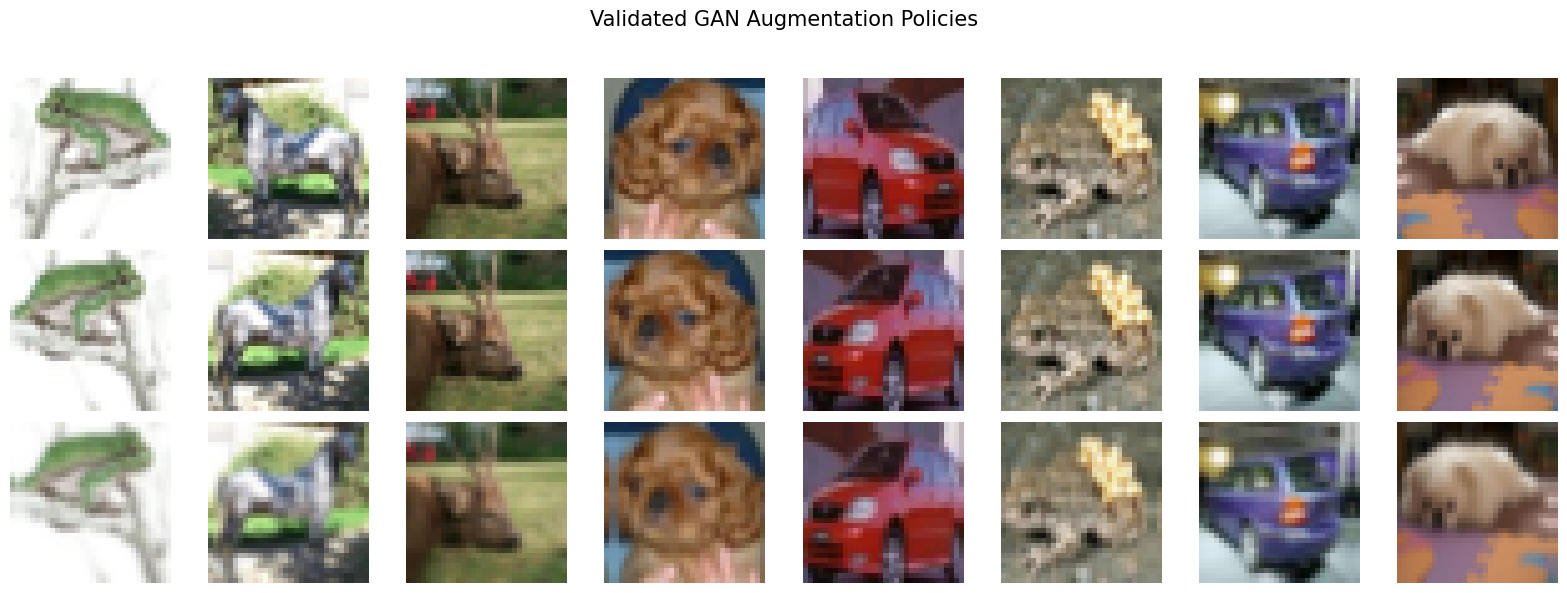

,Policy,Discriminator parameters,Input gradient created,Mean absolute input gradient
0,Horizontal flip,664129,True,0.000976
1,Horizontal flip + translation,664129,True,0.000619


Separate-call mean absolute difference, flip: 0.137095
Separate-call mean absolute difference, flip + translation: 0.223259
Both wrapped discriminators retain 664129 parameters.
Inference calls leave images unchanged.
Generator-path input gradients were created through both policies.
Augmentation preview saved: [local project directory]/grids/augmentation_policy_preview.png
No augmentation model has been trained yet.
Protected test set remains unused.


0

In [65]:
keras.backend.clear_session()

reset_run_seed(
    AUGMENTATION_TRAINING_SEED
)


augmentation_preview_rng = (
    np.random.default_rng(2401)
)

augmentation_preview_indices = (
    augmentation_preview_rng.choice(
        len(x_train_gan),
        size=8,
        replace=False,
    )
)

augmentation_preview_images = (
    tf.convert_to_tensor(
        x_train_gan[
            augmentation_preview_indices
        ],
        dtype=tf.float32,
    )
)


flip_policy_probe = (
    build_dcgan_augmentation_policy(
        policy_name="flip",
        augmentation_seed=(
            AUGMENTATION_TRAINING_SEED
        ),
    )
)

flip_translation_policy_probe = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            AUGMENTATION_TRAINING_SEED
        ),
    )
)


flip_preview_images = flip_policy_probe(
    augmentation_preview_images,
    training=True,
)

flip_translation_preview_images = (
    flip_translation_policy_probe(
        augmentation_preview_images,
        training=True,
    )
)


# Augmentation must be disabled during inference.
flip_inference_images = flip_policy_probe(
    augmentation_preview_images,
    training=False,
)

flip_translation_inference_images = (
    flip_translation_policy_probe(
        augmentation_preview_images,
        training=False,
    )
)


assert np.allclose(
    flip_inference_images.numpy(),
    augmentation_preview_images.numpy(),
    atol=1e-7,
)

assert np.allclose(
    flip_translation_inference_images.numpy(),
    augmentation_preview_images.numpy(),
    atol=1e-7,
)


for augmented_batch in [
    flip_preview_images,
    flip_translation_preview_images,
]:
    assert augmented_batch.shape == (
        8,
        32,
        32,
        3,
    )

    assert np.isfinite(
        augmented_batch.numpy()
    ).all()

    assert float(
        tf.reduce_min(
            augmented_batch
        ).numpy()
    ) >= -1.0001

    assert float(
        tf.reduce_max(
            augmented_batch
        ).numpy()
    ) <= 1.0001


# Separate policy calls must consume separate
# random draws from the same distribution.
independence_probe_images = (
    tf.convert_to_tensor(
        x_train_gan[:64],
        dtype=tf.float32,
    )
)

flip_call_a = flip_policy_probe(
    independence_probe_images,
    training=True,
)

flip_call_b = flip_policy_probe(
    independence_probe_images,
    training=True,
)

translation_call_a = (
    flip_translation_policy_probe(
        independence_probe_images,
        training=True,
    )
)

translation_call_b = (
    flip_translation_policy_probe(
        independence_probe_images,
        training=True,
    )
)


flip_separate_call_difference = float(
    tf.reduce_mean(
        tf.abs(
            flip_call_a
            - flip_call_b
        )
    ).numpy()
)

translation_separate_call_difference = float(
    tf.reduce_mean(
        tf.abs(
            translation_call_a
            - translation_call_b
        )
    ).numpy()
)


assert flip_separate_call_difference > 0.0

assert (
    translation_separate_call_difference
    > 0.0
)


# Build both wrapped discriminators.
flip_discriminator_probe = (
    AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER()
)

flip_translation_discriminator_probe = (
    AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER()
)


assert (
    flip_discriminator_probe.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

assert (
    flip_translation_discriminator_probe.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


# Verify gradients can pass from discriminator
# scores through each augmentation to its input.
augmentation_gradient_rows = []

for policy_label, discriminator_probe in [
    (
        "Horizontal flip",
        flip_discriminator_probe,
    ),
    (
        "Horizontal flip + translation",
        flip_translation_discriminator_probe,
    ),
]:
    gradient_input = tf.Variable(
        x_train_gan[:8],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        gradient_scores = (
            discriminator_probe(
                gradient_input,
                training=True,
            )
        )

        gradient_objective = (
            tf.reduce_mean(
                gradient_scores
            )
        )

    input_gradients = tape.gradient(
        gradient_objective,
        gradient_input,
    )

    assert input_gradients is not None

    assert np.isfinite(
        input_gradients.numpy()
    ).all()

    mean_absolute_gradient = float(
        tf.reduce_mean(
            tf.abs(
                input_gradients
            )
        ).numpy()
    )

    assert mean_absolute_gradient > 0.0

    augmentation_gradient_rows.append(
        {
            "Policy": policy_label,
            "Discriminator parameters": (
                discriminator_probe.count_params()
            ),
            "Input gradient created": True,
            "Mean absolute input gradient": (
                mean_absolute_gradient
            ),
        }
    )


augmentation_gradient_check_df = (
    pd.DataFrame(
        augmentation_gradient_rows
    )
)


AUGMENTATION_POLICY_PREVIEW_PATH = (
    GRIDS_DIR
    / "augmentation_policy_preview.png"
)


original_display_images = np.clip(
    (
        augmentation_preview_images.numpy()
        + 1.0
    )
    / 2.0,
    0.0,
    1.0,
)

flip_display_images = np.clip(
    (
        flip_preview_images.numpy()
        + 1.0
    )
    / 2.0,
    0.0,
    1.0,
)

flip_translation_display_images = (
    np.clip(
        (
            flip_translation_preview_images
            .numpy()
            + 1.0
        )
        / 2.0,
        0.0,
        1.0,
    )
)


fig, axes = plt.subplots(
    3,
    8,
    figsize=(16, 6),
)


for column_index in range(8):
    axes[0, column_index].imshow(
        original_display_images[
            column_index
        ]
    )

    axes[1, column_index].imshow(
        flip_display_images[
            column_index
        ]
    )

    axes[2, column_index].imshow(
        flip_translation_display_images[
            column_index
        ]
    )

    for row_index in range(3):
        axes[row_index, column_index].axis(
            "off"
        )


axes[0, 0].set_ylabel(
    "Original",
    fontsize=11,
)

axes[1, 0].set_ylabel(
    "Flip",
    fontsize=11,
)

axes[2, 0].set_ylabel(
    "Flip + translation",
    fontsize=11,
)


fig.suptitle(
    "Validated GAN Augmentation Policies",
    fontsize=15,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.95)
)

fig.savefig(
    AUGMENTATION_POLICY_PREVIEW_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


display(
    augmentation_gradient_check_df.round(8)
)


print(
    "Separate-call mean absolute difference, "
    "flip:",
    f"{flip_separate_call_difference:.6f}",
)

print(
    "Separate-call mean absolute difference, "
    "flip + translation:",
    (
        f"{translation_separate_call_difference:.6f}"
    ),
)

print(
    "Both wrapped discriminators retain",
    CURRENT_DISCRIMINATOR_PARAMETERS,
    "parameters.",
)

print(
    "Inference calls leave images unchanged."
)

print(
    "Generator-path input gradients were "
    "created through both policies."
)

print(
    "Augmentation preview saved:",
    AUGMENTATION_POLICY_PREVIEW_PATH,
)

print(
    "No augmentation model has been "
    "trained yet."
)

print(
    "Protected test set remains unused."
)


del augmentation_preview_images
del flip_preview_images
del flip_translation_preview_images
del flip_inference_images
del flip_translation_inference_images

del independence_probe_images
del flip_call_a
del flip_call_b
del translation_call_a
del translation_call_b

del flip_policy_probe
del flip_translation_policy_probe

del flip_discriminator_probe
del flip_translation_discriminator_probe

keras.backend.clear_session()
gc.collect()

### 11.2 Formal Augmentation Runs

The augmentation family now trains its two predeclared alternatives:

1. horizontal flipping;
2. horizontal flipping with mild translation.

The completed unaugmented seed-42 DCGAN remains the carried reference and is not retrained.

Both alternatives receive fresh generator, discriminator and optimiser states. Resetting the complete seed before each run gives both alternatives the same seed-42 generator initialisation and training-data order, while the augmentation policy remains the intended changed factor.

Each formal run receives:

- 100 epochs;
- 782 batches per epoch;
- 78,200 generator updates;
- 78,200 discriminator updates;
- fixed-seed progression grids every 10 epochs;
- milestone weights at epochs 50, 70, 90 and 100;
- full checkpoint and history persistence.

Only Tier 1 training evidence is collected initially. Checkpoint FID and deeper evaluation will follow after both runs finish.

In [66]:
required_augmentation_training_objects = [
    "AUGMENTATION_FAMILY_NAME",
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_FLIP_RUN_ID",
    "AUGMENTATION_FLIP_TRANSLATION_RUN_ID",
    "AUGMENTATION_TRAINING_SEED",
    "AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER",
    "AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "REQUIRED_DCGAN_FAMILY_CONFIG_KEYS",
    "build_dcgan_generator",
    "build_dcgan_discriminator",
    "run_dcgan_family",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_augmentation_training_objects = [
    name
    for name in required_augmentation_training_objects
    if name not in globals()
]

assert not missing_augmentation_training_objects, (
    "Incomplete augmentation-training setup:\n"
    + "\n".join(
        missing_augmentation_training_objects
    )
)


AUGMENTATION_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

AUGMENTATION_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

AUGMENTATION_CHECKPOINT_INTERVAL = 10


assert AUGMENTATION_TRAINING_SEED == 42

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert AUGMENTATION_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert AUGMENTATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)


AUGMENTATION_FAMILY_CONFIGURATIONS = [
    {
        "run_id": (
            AUGMENTATION_FLIP_RUN_ID
        ),
        "configuration_label": (
            "DCGAN Horizontal Flip"
        ),
        "main_change": (
            "Symmetric on-the-fly horizontal "
            "flipping inside the discriminator"
        ),
        "training_seed": (
            AUGMENTATION_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
    {
        "run_id": (
            AUGMENTATION_FLIP_TRANSLATION_RUN_ID
        ),
        "configuration_label": (
            "DCGAN Horizontal Flip and Translation"
        ),
        "main_change": (
            "Symmetric on-the-fly horizontal "
            "flipping and two-pixel translation "
            "inside the discriminator"
        ),
        "training_seed": (
            AUGMENTATION_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    },
]


assert len(
    AUGMENTATION_FAMILY_CONFIGURATIONS
) == 2

assert len(
    {
        configuration["run_id"]
        for configuration
        in AUGMENTATION_FAMILY_CONFIGURATIONS
    }
) == 2


for configuration in (
    AUGMENTATION_FAMILY_CONFIGURATIONS
):
    missing_configuration_keys = [
        key
        for key
        in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
        if key not in configuration
    ]

    assert not missing_configuration_keys, (
        f"{configuration['run_id']} is missing:\n"
        + "\n".join(
            missing_configuration_keys
        )
    )

    assert (
        configuration["generator_builder"]
        is build_dcgan_generator
    )

    assert callable(
        configuration[
            "discriminator_builder"
        ]
    )

    assert (
        configuration["training_seed"]
        == 42
    )

    assert (
        configuration[
            "generator_learning_rate"
        ]
        == 2e-4
    )

    assert (
        configuration[
            "discriminator_learning_rate"
        ]
        == 2e-4
    )


# Confirm that each builder creates a fresh,
# independent discriminator with the retained capacity.
keras.backend.clear_session()

reset_run_seed(
    AUGMENTATION_TRAINING_SEED
)

augmentation_flip_probe_discriminator = (
    AUGMENTATION_FLIP_DISCRIMINATOR_BUILDER()
)

keras.backend.clear_session()

reset_run_seed(
    AUGMENTATION_TRAINING_SEED
)

augmentation_flip_translation_probe_discriminator = (
    AUGMENTATION_FLIP_TRANSLATION_DISCRIMINATOR_BUILDER()
)


assert (
    augmentation_flip_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

assert (
    augmentation_flip_translation_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)

assert (
    augmentation_flip_probe_discriminator
    is not
    augmentation_flip_translation_probe_discriminator
)


augmentation_family_plan_df = pd.DataFrame(
    [
        {
            "Order": 1,
            "Run ID": (
                AUGMENTATION_REFERENCE_RUN_ID
            ),
            "Configuration": (
                "No augmentation"
            ),
            "Role": "Carried reference",
            "Training action": (
                "Reuse completed seed-42 run"
            ),
            "Training seed": 42,
        },
        {
            "Order": 2,
            "Run ID": (
                AUGMENTATION_FLIP_RUN_ID
            ),
            "Configuration": (
                "Horizontal flip"
            ),
            "Role": "New Tier 1 candidate",
            "Training action": (
                "Train 100 epochs"
            ),
            "Training seed": 42,
        },
        {
            "Order": 3,
            "Run ID": (
                AUGMENTATION_FLIP_TRANSLATION_RUN_ID
            ),
            "Configuration": (
                "Horizontal flip + translation"
            ),
            "Role": "New Tier 1 candidate",
            "Training action": (
                "Train 100 epochs"
            ),
            "Training seed": 42,
        },
    ]
)


display(
    augmentation_family_plan_df
)


print(
    "Two formal augmentation "
    "configurations validated."
)

print(
    "The unaugmented reference "
    "will not be retrained."
)

print(
    "Both alternatives retain",
    CURRENT_GENERATOR_PARAMETERS,
    "generator parameters and",
    CURRENT_DISCRIMINATOR_PARAMETERS,
    "discriminator parameters.",
)

print(
    "Ordinary unaugmented generator "
    "outputs will be saved in grids."
)

print("Protected test set remains unused.")


del augmentation_flip_probe_discriminator
del augmentation_flip_translation_probe_discriminator

keras.backend.clear_session()
gc.collect()

,Order,Run ID,Configuration,Role,Training action,Training seed
0,1,G02_dcgan_seed42,No augmentation,Carried reference,Reuse completed seed-42 run,42
1,2,G08_augmentation_flip_seed42,Horizontal flip,New Tier 1 candidate,Train 100 epochs,42
2,3,G08_augmentation_fliptranslation_seed42,Horizontal flip + translation,New Tier 1 candidate,Train 100 epochs,42


Two formal augmentation configurations validated.
The unaugmented reference will not be retrained.
Both alternatives retain 1085187 generator parameters and 664129 discriminator parameters.
Ordinary unaugmented generator outputs will be saved in grids.
Protected test set remains unused.


0

In [70]:
keras.backend.clear_session()


augmentation_family_training_df = (
    run_dcgan_family(
        family_name=(
            AUGMENTATION_FAMILY_NAME
        ),
        configurations=(
            AUGMENTATION_FAMILY_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=(
            AUGMENTATION_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            AUGMENTATION_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            AUGMENTATION_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)


display(
    augmentation_family_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "batches_per_epoch",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


assert (
    augmentation_family_training_df[
        "epochs_completed"
    ].astype(int).eq(
        AUGMENTATION_TARGET_EPOCHS
    ).all()
)

assert (
    augmentation_family_training_df[
        "batches_per_epoch"
    ].astype(int).eq(782).all()
)

assert (
    augmentation_family_training_df[
        "generator_updates"
    ].astype(int).eq(78_200).all()
)

assert (
    augmentation_family_training_df[
        "discriminator_updates"
    ].astype(int).eq(78_200).all()
)


print(
    "Both formal augmentation "
    "training calls completed."
)

print(
    "No augmentation checkpoint "
    "or family winner has been selected."
)

print(
    "The unaugmented reference remains "
    "the carried setting during screening."
)

print("Protected test set remains unused.")

Declared family: Data augmentation


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G08_augmentation_flip_seed42,DCGAN Horizontal Flip,Symmetric on-the-fly horizontal flipping insid...,42,100,64,0.0002,0.0002,0.5,0.999
1,2,G08_augmentation_fliptranslation_seed42,DCGAN Horizontal Flip and Translation,Symmetric on-the-fly horizontal flipping and t...,42,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/2
Run ID: G08_augmentation_flip_seed42
Configuration: DCGAN Horizontal Flip
Main change: Symmetric on-the-fly horizontal flipping inside the discriminator
Training new run G08_augmentation_flip_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.4212 | D loss: 0.1700 | Real: 0.8834 | Fake: 0.1155 | Time: 17.1s
Epoch 002/100 | G loss: 1.0119 | D loss: 0.1904 | Real: 0.8626 | Fake: 0.1341 | Time: 12.6s
Epoch 003/100 | G loss: 1.5319 | D loss: 0.2443 | Real: 0.8257 | Fake: 0.1717 | Time: 12.5s
Epoch 004/100 | G loss: 0.9227 | D loss: 0.1662 | Real: 0.8841 | Fake: 0.1152 | Time: 12.6s
Epoch 005/100 | G loss: 0.5634 | D loss: 0.0895 | Real: 0.9331 | Fake: 0.0660 | Time: 12.6s
Epoch 006/100 | G loss: 1.2036 | D loss: 0.1636 | Real: 0.8938 | Fake: 0.1054 | Time: 12.5s
Epoch 007/100 | G loss: 0.9163 | D loss: 0.1086 | Real: 0.9231 | Fake: 0.0768 | Time: 12.7s
Epoch 008/100 | 

,run_id,configuration_label,action,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G08_augmentation_flip_seed42,DCGAN Horizontal Flip,trained_new,100,782,78200,78200,1085187,664129,21.2089
1,G08_augmentation_fliptranslation_seed42,DCGAN Horizontal Flip and Translation,trained_new,100,782,78200,78200,1085187,664129,22.4793


Both formal augmentation training calls completed.
No augmentation checkpoint or family winner has been selected.
The unaugmented reference remains the carried setting during screening.
Protected test set remains unused.


### 11.3 Tier 1 Artifact Audit

Before evaluating either augmentation candidate, the persisted training artifacts are verified independently of the completed family-training call.

For both runs, the audit checks:

- a complete and finite 100-epoch history;
- a resumable checkpoint at epoch 100;
- fixed-seed progression grids every 10 epochs;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100;
- the expected 782 batches per epoch;
- the expected 78,200 updates per network;
- a positive recorded training time.

In [47]:
# Evaluation-local augmentation metadata.

required_augmentation_audit_base_objects = [
    "CURRENT_BATCH_SIZE",
    "STANDARD_DCGAN_HISTORY_COLUMNS",
    "inspect_dcgan_training_status",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_augmentation_audit_base_objects = [
    name
    for name in required_augmentation_audit_base_objects
    if name not in globals()
]

assert not missing_augmentation_audit_base_objects, (
    "Incomplete augmentation evaluation setup:\n"
    + "\n".join(
        missing_augmentation_audit_base_objects
    )
)


# Re-declare only the persisted run metadata lost
# when the Colab runtime was changed.
AUGMENTATION_FLIP_RUN_ID = (
    "G08_augmentation_flip_seed42"
)

AUGMENTATION_FLIP_TRANSLATION_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

AUGMENTATION_TARGET_EPOCHS = 100

AUGMENTATION_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)

AUGMENTATION_CHECKPOINT_INTERVAL = 10


AUGMENTATION_BATCHES_PER_EPOCH = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

AUGMENTATION_EXPECTED_UPDATES = (
    AUGMENTATION_BATCHES_PER_EPOCH
    * AUGMENTATION_TARGET_EPOCHS
)


assert len(x_train_gan) == 50_000
assert CURRENT_BATCH_SIZE == 64

assert AUGMENTATION_BATCHES_PER_EPOCH == 782
assert AUGMENTATION_EXPECTED_UPDATES == 78_200

assert AUGMENTATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)


augmentation_audit_specs = [
    {
        "Configuration": "Horizontal flip",
        "Run ID": AUGMENTATION_FLIP_RUN_ID,
    },
    {
        "Configuration": (
            "Horizontal flip + translation"
        ),
        "Run ID": (
            AUGMENTATION_FLIP_TRANSLATION_RUN_ID
        ),
    },
]


assert len(augmentation_audit_specs) == 2

assert len(
    {
        specification["Run ID"]
        for specification
        in augmentation_audit_specs
    }
) == 2


print(
    "Augmentation artifact-audit "
    "configuration restored."
)

print(
    "Run 1:",
    AUGMENTATION_FLIP_RUN_ID,
)

print(
    "Run 2:",
    AUGMENTATION_FLIP_TRANSLATION_RUN_ID,
)

print(
    "Expected batches per epoch:",
    AUGMENTATION_BATCHES_PER_EPOCH,
)

print(
    "Expected updates per network:",
    AUGMENTATION_EXPECTED_UPDATES,
)

print(
    "No model has been built or trained."
)

print("Protected test set remains unused.")

Augmentation artifact-audit configuration restored.
Run 1: G08_augmentation_flip_seed42
Run 2: G08_augmentation_fliptranslation_seed42
Expected batches per epoch: 782
Expected updates per network: 78200
No model has been built or trained.
Protected test set remains unused.


In [48]:
augmentation_artifact_audit_rows = []


for specification in augmentation_audit_specs:
    configuration = specification[
        "Configuration"
    ]

    run_id = specification["Run ID"]


    training_status = (
        inspect_dcgan_training_status(
            run_id=run_id,
            target_epochs=(
                AUGMENTATION_TARGET_EPOCHS
            ),
            checkpoint_root=CHECKPOINTS_DIR,
            weights_dir=WEIGHTS_DIR,
            histories_dir=HISTORIES_DIR,
            grids_dir=GRIDS_DIR,
            milestone_epochs=(
                AUGMENTATION_MILESTONE_EPOCHS
            ),
            checkpoint_interval=(
                AUGMENTATION_CHECKPOINT_INTERVAL
            ),
        )
    )


    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    assert history_path.is_file(), (
        f"Missing history:\n{history_path}"
    )


    history_df = pd.read_csv(
        history_path
    )

    missing_history_columns = [
        column
        for column
        in STANDARD_DCGAN_HISTORY_COLUMNS
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{run_id} history is missing:\n"
        + "\n".join(
            missing_history_columns
        )
    )


    history_df = (
        history_df[
            STANDARD_DCGAN_HISTORY_COLUMNS
        ]
        .copy()
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    assert len(history_df) == 100

    assert np.array_equal(
        history_df[
            "epoch"
        ].to_numpy(dtype=np.int64),
        np.arange(
            1,
            101,
            dtype=np.int64,
        ),
    )

    assert np.isfinite(
        history_df[
            STANDARD_DCGAN_HISTORY_COLUMNS
        ].to_numpy(dtype=np.float64)
    ).all()


    grid_paths = [
        GRIDS_DIR
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}.png"
        )
        for epoch in range(
            AUGMENTATION_CHECKPOINT_INTERVAL,
            AUGMENTATION_TARGET_EPOCHS + 1,
            AUGMENTATION_CHECKPOINT_INTERVAL,
        )
    ]


    generator_milestone_paths = [
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
        for epoch
        in AUGMENTATION_MILESTONE_EPOCHS
    ]


    discriminator_milestone_paths = [
        WEIGHTS_DIR
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
        for epoch
        in AUGMENTATION_MILESTONE_EPOCHS
    ]


    for artifact_path in (
        grid_paths
        + generator_milestone_paths
        + discriminator_milestone_paths
    ):
        assert artifact_path.is_file(), (
            "Missing augmentation artifact:\n"
            f"{artifact_path}"
        )

        assert artifact_path.stat().st_size > 0, (
            "Empty augmentation artifact:\n"
            f"{artifact_path}"
        )


    latest_checkpoint = (
        tf.train.latest_checkpoint(
            str(
                CHECKPOINTS_DIR
                / run_id
            )
        )
    )

    assert latest_checkpoint is not None

    assert training_status["status"] == "completed"

    assert (
        training_status["checkpoint_epoch"]
        == AUGMENTATION_TARGET_EPOCHS
    )


    recorded_training_time = float(
        history_df[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    assert recorded_training_time > 0.0


    augmentation_artifact_audit_rows.append(
        {
            "Configuration": configuration,
            "Run ID": run_id,
            "Status": (
                training_status["status"]
            ),
            "History rows": len(
                history_df
            ),
            "Checkpoint epoch": (
                training_status[
                    "checkpoint_epoch"
                ]
            ),
            "Progression grids": len(
                grid_paths
            ),
            "Generator milestones": len(
                generator_milestone_paths
            ),
            "Discriminator milestones": len(
                discriminator_milestone_paths
            ),
            "Batches per epoch": (
                AUGMENTATION_BATCHES_PER_EPOCH
            ),
            "Expected generator updates": (
                AUGMENTATION_EXPECTED_UPDATES
            ),
            "Expected discriminator updates": (
                AUGMENTATION_EXPECTED_UPDATES
            ),
            "Finite history": True,
            "Training time minutes": (
                recorded_training_time
            ),
            "Latest checkpoint": (
                latest_checkpoint
            ),
        }
    )


augmentation_artifact_audit_df = (
    pd.DataFrame(
        augmentation_artifact_audit_rows
    )
)


assert len(
    augmentation_artifact_audit_df
) == 2

assert (
    augmentation_artifact_audit_df[
        "Status"
    ].eq("completed").all()
)

assert (
    augmentation_artifact_audit_df[
        "History rows"
    ].eq(100).all()
)

assert (
    augmentation_artifact_audit_df[
        "Checkpoint epoch"
    ].eq(100).all()
)

assert (
    augmentation_artifact_audit_df[
        "Progression grids"
    ].eq(10).all()
)

assert (
    augmentation_artifact_audit_df[
        "Generator milestones"
    ].eq(4).all()
)

assert (
    augmentation_artifact_audit_df[
        "Discriminator milestones"
    ].eq(4).all()
)


AUGMENTATION_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / "augmentation_tier1_artifact_audit.csv"
)

augmentation_artifact_audit_df.to_csv(
    AUGMENTATION_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    augmentation_artifact_audit_df[
        [
            "Configuration",
            "Run ID",
            "Status",
            "History rows",
            "Checkpoint epoch",
            "Progression grids",
            "Generator milestones",
            "Discriminator milestones",
            "Batches per epoch",
            "Expected generator updates",
            "Expected discriminator updates",
            "Finite history",
            "Training time minutes",
        ]
    ].round(4)
)


print(
    "Both augmentation artifact "
    "audits passed."
)

print(
    "Artifact audit saved:",
    AUGMENTATION_ARTIFACT_AUDIT_PATH,
)

print(
    "No checkpoint or family winner "
    "has been selected."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Expected generator updates,Expected discriminator updates,Finite history,Training time minutes
0,Horizontal flip,G08_augmentation_flip_seed42,completed,100,100,10,4,4,782,78200,78200,True,21.2089
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,completed,100,100,10,4,4,782,78200,78200,True,22.4793


Both augmentation artifact audits passed.
Artifact audit saved: [local project directory]/histories/augmentation_tier1_artifact_audit.csv
No checkpoint or family winner has been selected.
Protected test set remains unused.


### 11.4 Tier 1 Milestone Development FID

The two augmentation candidates are evaluated at epochs 50, 70, 90 and 100.

Each saved generator checkpoint produces 5,000 ordinary, unaugmented images using the fixed milestone-selection seed `1001`. The generated-image features are compared against the unchanged CIFAR-10 training-reference statistics.

Augmentation remains active only during training. It is not applied to generated images during FID evaluation.

The lowest-FID checkpoint for each candidate is treated as provisional until its fixed-seed progression and training stability are inspected.

In [49]:
required_augmentation_fid_objects = [
    "AUGMENTATION_FLIP_RUN_ID",
    "AUGMENTATION_FLIP_TRANSLATION_RUN_ID",
    "AUGMENTATION_MILESTONE_EPOCHS",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "FID_FEATURE_DIM",
    "MILESTONE_FID_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_augmentation_fid_objects = [
    name
    for name in required_augmentation_fid_objects
    if name not in globals()
]

assert not missing_augmentation_fid_objects, (
    "Incomplete augmentation milestone-FID setup:\n"
    + "\n".join(
        missing_augmentation_fid_objects
    )
)


assert AUGMENTATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert CURRENT_LATENT_DIM == 100
assert CURRENT_GENERATOR_PARAMETERS == 1_085_187

assert FID_SAMPLE_COUNT == 5_000
assert FID_FEATURE_DIM == 2_048
assert MILESTONE_FID_SEED == 1_001

assert real_fid_mean.shape == (
    FID_FEATURE_DIM,
)

assert real_fid_covariance.shape == (
    FID_FEATURE_DIM,
    FID_FEATURE_DIM,
)

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()

assert fid_feature_extractor.trainable is False


augmentation_milestone_fid_specs = [
    {
        "Configuration": "Horizontal flip",
        "Run ID": AUGMENTATION_FLIP_RUN_ID,
    },
    {
        "Configuration": (
            "Horizontal flip + translation"
        ),
        "Run ID": (
            AUGMENTATION_FLIP_TRANSLATION_RUN_ID
        ),
    },
]


AUGMENTATION_MILESTONE_FID_PATH = (
    HISTORIES_DIR
    / "augmentation_tier1_milestone_fid.csv"
)


print(
    "Augmentation milestone-FID "
    "contract validated."
)

print(
    "Candidates:",
    len(augmentation_milestone_fid_specs),
)

print(
    "Milestones per candidate:",
    len(AUGMENTATION_MILESTONE_EPOCHS),
)

print(
    "Generated images per checkpoint:",
    FID_SAMPLE_COUNT,
)

print(
    "FID sampling seed:",
    MILESTONE_FID_SEED,
)

print("Protected test set remains unused.")

Augmentation milestone-FID contract validated.
Candidates: 2
Milestones per candidate: 4
Generated images per checkpoint: 5000
FID sampling seed: 1001
Protected test set remains unused.


In [50]:
augmentation_fid_columns = [
    "configuration",
    "run_id",
    "training_seed",
    "epoch",
    "fid_seed",
    "sample_count",
    "fid",
]


if AUGMENTATION_MILESTONE_FID_PATH.is_file():
    augmentation_milestone_fid_df = (
        pd.read_csv(
            AUGMENTATION_MILESTONE_FID_PATH
        )
    )

    missing_saved_columns = [
        column
        for column in augmentation_fid_columns
        if column
        not in augmentation_milestone_fid_df.columns
    ]

    assert not missing_saved_columns, (
        "Saved augmentation FID file is missing:\n"
        + "\n".join(
            missing_saved_columns
        )
    )

    augmentation_milestone_fid_df = (
        augmentation_milestone_fid_df[
            augmentation_fid_columns
        ].copy()
    )

else:
    augmentation_milestone_fid_df = (
        pd.DataFrame(
            columns=augmentation_fid_columns
        )
    )


tf.keras.backend.clear_session()

augmentation_eval_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

assert (
    augmentation_eval_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


for specification in (
    augmentation_milestone_fid_specs
):
    configuration = specification[
        "Configuration"
    ]

    run_id = specification["Run ID"]


    for epoch in (
        AUGMENTATION_MILESTONE_EPOCHS
    ):
        existing_row = (
            augmentation_milestone_fid_df.loc[
                (
                    augmentation_milestone_fid_df[
                        "run_id"
                    ].astype(str)
                    == run_id
                )
                & (
                    pd.to_numeric(
                        augmentation_milestone_fid_df[
                            "epoch"
                        ],
                        errors="coerce",
                    )
                    == epoch
                )
                & (
                    pd.to_numeric(
                        augmentation_milestone_fid_df[
                            "fid_seed"
                        ],
                        errors="coerce",
                    )
                    == MILESTONE_FID_SEED
                )
                & (
                    pd.to_numeric(
                        augmentation_milestone_fid_df[
                            "sample_count"
                        ],
                        errors="coerce",
                    )
                    == FID_SAMPLE_COUNT
                )
            ]
        )


        if len(existing_row) == 1:
            existing_fid = float(
                existing_row["fid"].iloc[0]
            )

            print(
                f"{configuration}, epoch {epoch:03d} "
                f"already saved: FID {existing_fid:.4f}"
            )

            continue


        generator_weights_path = (
            WEIGHTS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}_"
                "generator.weights.h5"
            )
        )

        assert generator_weights_path.is_file(), (
            "Missing augmentation generator weights:\n"
            f"{generator_weights_path}"
        )


        augmentation_eval_generator.load_weights(
            generator_weights_path
        )


        generated_images = generate_images_uint8(
            generator=augmentation_eval_generator,
            sample_count=FID_SAMPLE_COUNT,
            latent_dim=CURRENT_LATENT_DIM,
            seed=MILESTONE_FID_SEED,
        )

        assert generated_images.shape == (
            FID_SAMPLE_COUNT,
            32,
            32,
            3,
        )

        assert generated_images.dtype == np.uint8


        generated_features = (
            extract_inception_features(
                images_uint8=generated_images,
                feature_extractor=(
                    fid_feature_extractor
                ),
                batch_size=FID_BATCH_SIZE,
            )
        )

        assert generated_features.shape == (
            FID_SAMPLE_COUNT,
            FID_FEATURE_DIM,
        )

        assert np.isfinite(
            generated_features
        ).all()


        (
            generated_mean,
            generated_covariance,
        ) = calculate_feature_statistics(
            generated_features
        )


        fid_value = (
            calculate_fid_from_statistics(
                real_fid_mean,
                real_fid_covariance,
                generated_mean,
                generated_covariance,
            )
        )

        assert np.isfinite(fid_value)


        new_row = pd.DataFrame(
            [
                {
                    "configuration": configuration,
                    "run_id": run_id,
                    "training_seed": 42,
                    "epoch": int(epoch),
                    "fid_seed": int(
                        MILESTONE_FID_SEED
                    ),
                    "sample_count": int(
                        FID_SAMPLE_COUNT
                    ),
                    "fid": float(fid_value),
                }
            ]
        )


        augmentation_milestone_fid_df = (
            augmentation_milestone_fid_df.loc[
                ~(
                    (
                        augmentation_milestone_fid_df[
                            "run_id"
                        ].astype(str)
                        == run_id
                    )
                    & (
                        pd.to_numeric(
                            augmentation_milestone_fid_df[
                                "epoch"
                            ],
                            errors="coerce",
                        )
                        == epoch
                    )
                )
            ]
        )


        augmentation_milestone_fid_df = (
            pd.concat(
                [
                    augmentation_milestone_fid_df,
                    new_row,
                ],
                ignore_index=True,
            )
            .sort_values(
                [
                    "run_id",
                    "epoch",
                ]
            )
            .reset_index(drop=True)
        )


        augmentation_milestone_fid_df.to_csv(
            AUGMENTATION_MILESTONE_FID_PATH,
            index=False,
        )


        print(
            f"{configuration}, epoch {epoch:03d}: "
            f"FID {fid_value:.4f}"
        )


        del generated_images
        del generated_features
        del generated_mean
        del generated_covariance

        gc.collect()


del augmentation_eval_generator

tf.keras.backend.clear_session()
gc.collect()


current_augmentation_run_ids = {
    specification["Run ID"]
    for specification
    in augmentation_milestone_fid_specs
}

augmentation_milestone_fid_df = (
    augmentation_milestone_fid_df.loc[
        augmentation_milestone_fid_df[
            "run_id"
        ].astype(str).isin(
            current_augmentation_run_ids
        )
    ]
    .sort_values(
        [
            "configuration",
            "epoch",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    augmentation_milestone_fid_df
) == 8

assert (
    augmentation_milestone_fid_df[
        "run_id"
    ].nunique()
    == 2
)

assert (
    augmentation_milestone_fid_df.groupby(
        "run_id"
    )["epoch"].nunique().eq(4).all()
)

assert set(
    augmentation_milestone_fid_df[
        "epoch"
    ].astype(int)
) == {
    50,
    70,
    90,
    100,
}

assert np.isfinite(
    augmentation_milestone_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


augmentation_milestone_fid_df.to_csv(
    AUGMENTATION_MILESTONE_FID_PATH,
    index=False,
)


display(
    augmentation_milestone_fid_df[
        [
            "configuration",
            "epoch",
            "fid_seed",
            "sample_count",
            "fid",
        ]
    ].round(4)
)


print(
    "Augmentation milestone FID saved:",
    AUGMENTATION_MILESTONE_FID_PATH,
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_510/1904958872.py:246: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


Horizontal flip, epoch 050: FID 42.1467


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Horizontal flip, epoch 070: FID 38.7875


...

Horizontal flip + translation, epoch 090: FID 36.1426


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Horizontal flip + translation, epoch 100: FID 35.6765


,configuration,epoch,fid_seed,sample_count,fid
0,Horizontal flip,50,1001,5000,42.1467
1,Horizontal flip,70,1001,5000,38.7875
2,Horizontal flip,90,1001,5000,37.6445
3,Horizontal flip,100,1001,5000,37.3927
4,Horizontal flip + translation,50,1001,5000,40.3972
5,Horizontal flip + translation,70,1001,5000,37.8871
6,Horizontal flip + translation,90,1001,5000,36.1426
7,Horizontal flip + translation,100,1001,5000,35.6765


Augmentation milestone FID saved: [local project directory]/histories/augmentation_tier1_milestone_fid.csv
Protected test set remains unused.


In [51]:
augmentation_provisional_rows = []


for specification in (
    augmentation_milestone_fid_specs
):
    configuration = specification[
        "Configuration"
    ]

    run_id = specification["Run ID"]

    configuration_rows = (
        augmentation_milestone_fid_df.loc[
            augmentation_milestone_fid_df[
                "run_id"
            ].astype(str)
            == run_id
        ]
        .sort_values(
            [
                "fid",
                "epoch",
            ],
            ascending=[
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    assert len(configuration_rows) == 4

    lowest_fid_row = (
        configuration_rows.iloc[0]
    )


    augmentation_provisional_rows.append(
        {
            "Configuration": configuration,
            "Run ID": run_id,
            "Provisional epoch": int(
                lowest_fid_row["epoch"]
            ),
            "Provisional milestone FID": float(
                lowest_fid_row["fid"]
            ),
            "Checkpoint status": (
                "Pending grid and stability review"
            ),
        }
    )


augmentation_tier1_checkpoint_screen_df = (
    pd.DataFrame(
        augmentation_provisional_rows
    )
)


AUGMENTATION_PROVISIONAL_EPOCHS = {
    row["Run ID"]: int(
        row["Provisional epoch"]
    )
    for _, row in (
        augmentation_tier1_checkpoint_screen_df
        .iterrows()
    )
}

AUGMENTATION_PROVISIONAL_FIDS = {
    row["Run ID"]: float(
        row["Provisional milestone FID"]
    )
    for _, row in (
        augmentation_tier1_checkpoint_screen_df
        .iterrows()
    )
}


AUGMENTATION_TIER1_CHECKPOINT_SCREEN_PATH = (
    HISTORIES_DIR
    / (
        "augmentation_tier1_"
        "checkpoint_screen.csv"
    )
)

augmentation_tier1_checkpoint_screen_df.to_csv(
    AUGMENTATION_TIER1_CHECKPOINT_SCREEN_PATH,
    index=False,
)


display(
    augmentation_tier1_checkpoint_screen_df.round(4)
)


print(
    "Provisional checkpoint screen saved:",
    AUGMENTATION_TIER1_CHECKPOINT_SCREEN_PATH,
)

print(
    "These checkpoints are not locked yet."
)

print(
    "No augmentation family winner "
    "has been selected."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Provisional epoch,Provisional milestone FID,Checkpoint status
0,Horizontal flip,G08_augmentation_flip_seed42,100,37.3927,Pending grid and stability review
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,100,35.6765,Pending grid and stability review


Provisional checkpoint screen saved: [local project directory]/histories/augmentation_tier1_checkpoint_screen.csv
These checkpoints are not locked yet.
No augmentation family winner has been selected.
Protected test set remains unused.


### 11.5 Tier 1 Progression and Stability Review

The provisional epoch-100 checkpoints are reviewed against the complete milestone progression and training trajectories.

This review checks for:

- visual improvement or deterioration from epochs 50 to 100;
- obvious collapse or excessive repetition;
- abrupt training instability;
- late-training discriminator dominance;
- whether the lowest-FID checkpoint has a visual or stability reason to be rejected.

Losses and discriminator scores are diagnostic only. They do not directly measure generated-image quality.

No augmentation checkpoint or family winner is selected in this subsection.

In [54]:
required_augmentation_progression_objects = [
    "augmentation_milestone_fid_specs",
    "augmentation_milestone_fid_df",
    "AUGMENTATION_MILESTONE_EPOCHS",
    "AUGMENTATION_PROVISIONAL_EPOCHS",
    "GRIDS_DIR",
]

missing_augmentation_progression_objects = [
    name
    for name in required_augmentation_progression_objects
    if name not in globals()
]

assert not missing_augmentation_progression_objects, (
    "Incomplete augmentation progression setup:\n"
    + "\n".join(
        missing_augmentation_progression_objects
    )
)


AUGMENTATION_TIER1_PROGRESSION_PATH = (
    GRIDS_DIR
    / "augmentation_tier1_milestone_progression.png"
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(20, 10),
)


for row_index, specification in enumerate(
    augmentation_milestone_fid_specs
):
    configuration = specification["Configuration"]
    run_id = specification["Run ID"]

    fid_by_epoch = (
        augmentation_milestone_fid_df.loc[
            augmentation_milestone_fid_df[
                "run_id"
            ].astype(str)
            == run_id
        ]
        .set_index("epoch")["fid"]
        .astype(float)
        .to_dict()
    )

    provisional_epoch = (
        AUGMENTATION_PROVISIONAL_EPOCHS[
            run_id
        ]
    )

    for column_index, epoch in enumerate(
        AUGMENTATION_MILESTONE_EPOCHS
    ):
        grid_path = (
            GRIDS_DIR
            / (
                f"{run_id}_"
                f"epoch{epoch:03d}.png"
            )
        )

        assert grid_path.is_file(), (
            f"Missing milestone grid:\n{grid_path}"
        )

        grid_image = plt.imread(
            grid_path
        )

        status_label = (
            "Provisional lowest FID"
            if epoch == provisional_epoch
            else "Milestone"
        )

        axis = axes[
            row_index,
            column_index,
        ]

        axis.imshow(
            grid_image
        )

        axis.set_title(
            (
                f"{configuration}\n"
                f"Epoch {epoch} | "
                f"FID {fid_by_epoch[epoch]:.4f}\n"
                f"{status_label}"
            ),
            fontsize=11,
        )

        axis.axis("off")


fig.suptitle(
    "Augmentation Tier 1 Milestone Progression",
    fontsize=16,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.96)
)

fig.savefig(
    AUGMENTATION_TIER1_PROGRESSION_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "Combined augmentation progression saved:",
    AUGMENTATION_TIER1_PROGRESSION_PATH,
)

print(
    "No checkpoint or family winner "
    "has been selected."
)

print("Protected test set remains unused.")

Combined augmentation progression saved: [local project directory]/grids/augmentation_tier1_milestone_progression.png
No checkpoint or family winner has been selected.
Protected test set remains unused.


In [55]:
required_augmentation_trajectory_objects = [
    "AUGMENTATION_FLIP_RUN_ID",
    "AUGMENTATION_FLIP_TRANSLATION_RUN_ID",
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_augmentation_trajectory_objects = [
    name
    for name in required_augmentation_trajectory_objects
    if name not in globals()
]

assert not missing_augmentation_trajectory_objects, (
    "Incomplete augmentation trajectory setup:\n"
    + "\n".join(
        missing_augmentation_trajectory_objects
    )
)


augmentation_history_specs = [
    {
        "label": "Horizontal flip",
        "history_path": (
            HISTORIES_DIR
            / f"{AUGMENTATION_FLIP_RUN_ID}.csv"
        ),
    },
    {
        "label": (
            "Horizontal flip + translation"
        ),
        "history_path": (
            HISTORIES_DIR
            / (
                f"{AUGMENTATION_FLIP_TRANSLATION_RUN_ID}"
                ".csv"
            )
        ),
    },
]


for specification in augmentation_history_specs:
    assert specification[
        "history_path"
    ].is_file(), (
        "Missing augmentation history:\n"
        f"{specification['history_path']}"
    )


AUGMENTATION_TIER1_TRAJECTORY_PATH = (
    GRIDS_DIR
    / "augmentation_tier1_training_trajectories.png"
)


plot_dcgan_history_comparison(
    history_specs=augmentation_history_specs,
    title=(
        "Augmentation Tier 1 "
        "Training Trajectories"
    ),
    output_path=(
        AUGMENTATION_TIER1_TRAJECTORY_PATH
    ),
)


print(
    "Augmentation trajectory plot saved:",
    AUGMENTATION_TIER1_TRAJECTORY_PATH,
)

print(
    "Training trajectories are diagnostic only."
)

print("Protected test set remains unused.")

Augmentation trajectory plot saved: [local project directory]/grids/augmentation_tier1_training_trajectories.png
Training trajectories are diagnostic only.
Protected test set remains unused.


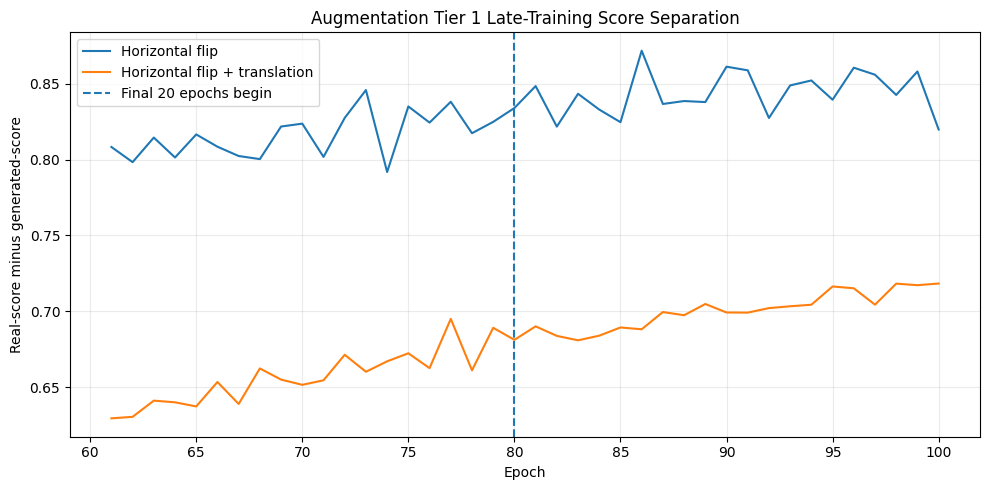

,Configuration,Window,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean
0,Horizontal flip,Epochs 61–80,3.9019,0.1497,0.1410,0.0166,0.9083,0.0914,0.8169,12.6823
1,Horizontal flip,Epochs 81–100,4.3851,0.1538,0.1203,0.0143,0.9219,0.0778,0.8441,12.6507
2,Horizontal flip + translation,Epochs 61–80,2.6491,0.0957,0.2470,0.0161,0.8287,0.1710,0.6577,13.3859
3,Horizontal flip + translation,Epochs 81–100,2.9404,0.1009,0.2166,0.0099,0.8503,0.1495,0.7008,13.3465


Late-training stability saved: [local project directory]/histories/augmentation_tier1_late_stability.csv
Score-separation plot saved: [local project directory]/grids/augmentation_tier1_late_score_separation.png
No image-quality conclusion is made from losses or scores alone.
No checkpoint or family winner has been selected.
Protected test set remains unused.


In [56]:
augmentation_history_frames = {
    specification["label"]: (
        pd.read_csv(
            specification["history_path"]
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )
    for specification in augmentation_history_specs
}


augmentation_late_stability_rows = []


for configuration, history_df in (
    augmentation_history_frames.items()
):
    required_history_columns = [
        "epoch",
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
        "epoch_time_seconds",
    ]

    missing_history_columns = [
        column
        for column in required_history_columns
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{configuration} history is missing:\n"
        + "\n".join(
            missing_history_columns
        )
    )

    assert len(history_df) == 100

    assert np.isfinite(
        history_df[
            required_history_columns
        ].to_numpy(dtype=np.float64)
    ).all()


    for start_epoch, end_epoch, label in [
        (61, 80, "Epochs 61–80"),
        (81, 100, "Epochs 81–100"),
    ]:
        window_df = history_df.loc[
            history_df["epoch"].between(
                start_epoch,
                end_epoch,
            )
        ].copy()

        assert len(window_df) == 20

        score_separation = (
            window_df["real_score"]
            - window_df["fake_score"]
        )

        augmentation_late_stability_rows.append(
            {
                "Configuration": configuration,
                "Window": label,
                "Generator loss mean": (
                    window_df[
                        "generator_loss"
                    ].mean()
                ),
                "Generator loss SD": (
                    window_df[
                        "generator_loss"
                    ].std(ddof=1)
                ),
                "Discriminator loss mean": (
                    window_df[
                        "discriminator_loss"
                    ].mean()
                ),
                "Discriminator loss SD": (
                    window_df[
                        "discriminator_loss"
                    ].std(ddof=1)
                ),
                "Real score mean": (
                    window_df[
                        "real_score"
                    ].mean()
                ),
                "Fake score mean": (
                    window_df[
                        "fake_score"
                    ].mean()
                ),
                "Score separation mean": (
                    score_separation.mean()
                ),
                "Epoch time mean": (
                    window_df[
                        "epoch_time_seconds"
                    ].mean()
                ),
            }
        )


augmentation_late_stability_df = pd.DataFrame(
    augmentation_late_stability_rows
)


AUGMENTATION_TIER1_STABILITY_PATH = (
    HISTORIES_DIR
    / "augmentation_tier1_late_stability.csv"
)

augmentation_late_stability_df.to_csv(
    AUGMENTATION_TIER1_STABILITY_PATH,
    index=False,
)


AUGMENTATION_TIER1_SCORE_SEPARATION_PATH = (
    GRIDS_DIR
    / "augmentation_tier1_late_score_separation.png"
)


plt.figure(
    figsize=(10, 5)
)


for configuration, history_df in (
    augmentation_history_frames.items()
):
    late_history_df = history_df.loc[
        history_df["epoch"] >= 61
    ]

    score_separation = (
        late_history_df["real_score"]
        - late_history_df["fake_score"]
    )

    plt.plot(
        late_history_df["epoch"],
        score_separation,
        label=configuration,
    )


plt.axvline(
    80,
    linestyle="--",
    label="Final 20 epochs begin",
)

plt.xlabel("Epoch")

plt.ylabel(
    "Real-score minus generated-score"
)

plt.title(
    "Augmentation Tier 1 "
    "Late-Training Score Separation"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    AUGMENTATION_TIER1_SCORE_SEPARATION_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


display(
    augmentation_late_stability_df.round(4)
)


print(
    "Late-training stability saved:",
    AUGMENTATION_TIER1_STABILITY_PATH,
)

print(
    "Score-separation plot saved:",
    AUGMENTATION_TIER1_SCORE_SEPARATION_PATH,
)

print(
    "No image-quality conclusion is made "
    "from losses or scores alone."
)

print(
    "No checkpoint or family winner "
    "has been selected."
)

print("Protected test set remains unused.")

#### Tier 1 Checkpoint and Shortlist Decision

Epoch `100` is selected for both augmentation candidates.

For horizontal flipping, development FID improved from `42.1467` at epoch 50 to `37.3927` at epoch 100. The fixed-seed progression remained varied and did not show an obvious visual collapse or late deterioration. Although discriminator dominance increased during late training, this did not provide sufficient evidence to reject the lowest-FID checkpoint.

For horizontal flipping with translation, development FID improved from `40.3972` at epoch 50 to `35.6765` at epoch 100. Its progression also remained visually stable and varied. The trajectory was more balanced than flip-only training, with a final-20 score separation of `0.7008` rather than `0.8441`.

Horizontal flipping with translation achieved lower milestone FID at all four evaluated checkpoints:

| Epoch | Horizontal flip | Flip + translation | Difference favouring translation |
|---:|---:|---:|---:|
| 50 | `42.1467` | `40.3972` | `1.7495` |
| 70 | `38.7875` | `37.8871` | `0.9004` |
| 90 | `37.6445` | `36.1426` | `1.5019` |
| 100 | `37.3927` | `35.6765` | `1.7162` |

The `1.7162` epoch-100 advantage remains below the predeclared `2.0` practical FID margin. It is therefore insufficient for adoption, but the consistent FID direction and stronger adversarial balance make horizontal flipping with translation the strongest Tier 1 candidate.

The flip-only candidate does not advance further. Horizontal flipping with translation advances to Tier 2 against the reused unaugmented reference, `G02_dcgan_seed42`.

No augmentation setting has yet been carried forward.

In [57]:
required_augmentation_shortlist_objects = [
    "AUGMENTATION_FLIP_RUN_ID",
    "AUGMENTATION_FLIP_TRANSLATION_RUN_ID",
    "augmentation_milestone_fid_df",
    "augmentation_late_stability_df",
    "augmentation_artifact_audit_df",
    "HISTORIES_DIR",
]

missing_augmentation_shortlist_objects = [
    name
    for name in required_augmentation_shortlist_objects
    if name not in globals()
]

assert not missing_augmentation_shortlist_objects, (
    "Incomplete augmentation shortlist setup:\n"
    + "\n".join(
        missing_augmentation_shortlist_objects
    )
)


AUGMENTATION_REFERENCE_RUN_ID = (
    "G02_dcgan_seed42"
)

AUGMENTATION_FLIP_SELECTED_EPOCH = 100

AUGMENTATION_FLIP_TRANSLATION_SELECTED_EPOCH = 100

AUGMENTATION_TIER2_CANDIDATE_RUN_ID = (
    AUGMENTATION_FLIP_TRANSLATION_RUN_ID
)

AUGMENTATION_TIER2_CANDIDATE_LABEL = (
    "Horizontal flip + translation"
)

AUGMENTATION_PRACTICAL_FID_MARGIN = 2.0


augmentation_fid_pivot_df = (
    augmentation_milestone_fid_df
    .pivot(
        index="epoch",
        columns="configuration",
        values="fid",
    )
    .sort_index()
)


assert list(
    augmentation_fid_pivot_df.index.astype(int)
) == [
    50,
    70,
    90,
    100,
]


augmentation_flip_fid_by_epoch = (
    augmentation_fid_pivot_df[
        "Horizontal flip"
    ]
)

augmentation_translation_fid_by_epoch = (
    augmentation_fid_pivot_df[
        "Horizontal flip + translation"
    ]
)


assert (
    augmentation_translation_fid_by_epoch
    < augmentation_flip_fid_by_epoch
).all()


AUGMENTATION_FLIP_SELECTED_FID = float(
    augmentation_flip_fid_by_epoch.loc[100]
)

AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID = float(
    augmentation_translation_fid_by_epoch.loc[100]
)

AUGMENTATION_TIER1_FID_LEAD = float(
    AUGMENTATION_FLIP_SELECTED_FID
    - AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID
)


assert np.isclose(
    AUGMENTATION_FLIP_SELECTED_FID,
    37.3927,
    atol=5e-5,
)

assert np.isclose(
    AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID,
    35.6765,
    atol=5e-5,
)

assert np.isclose(
    AUGMENTATION_TIER1_FID_LEAD,
    1.7162,
    atol=5e-5,
)

assert (
    AUGMENTATION_TIER1_FID_LEAD
    < AUGMENTATION_PRACTICAL_FID_MARGIN
)


flip_final_window_row = (
    augmentation_late_stability_df.loc[
        (
            augmentation_late_stability_df[
                "Configuration"
            ]
            == "Horizontal flip"
        )
        & (
            augmentation_late_stability_df[
                "Window"
            ]
            == "Epochs 81–100"
        )
    ]
)

translation_final_window_row = (
    augmentation_late_stability_df.loc[
        (
            augmentation_late_stability_df[
                "Configuration"
            ]
            == "Horizontal flip + translation"
        )
        & (
            augmentation_late_stability_df[
                "Window"
            ]
            == "Epochs 81–100"
        )
    ]
)


assert len(flip_final_window_row) == 1
assert len(translation_final_window_row) == 1


flip_final_score_separation = float(
    flip_final_window_row[
        "Score separation mean"
    ].iloc[0]
)

translation_final_score_separation = float(
    translation_final_window_row[
        "Score separation mean"
    ].iloc[0]
)


assert (
    translation_final_score_separation
    < flip_final_score_separation
)


flip_runtime_minutes = float(
    augmentation_artifact_audit_df.loc[
        augmentation_artifact_audit_df[
            "Run ID"
        ]
        == AUGMENTATION_FLIP_RUN_ID,
        "Training time minutes",
    ].iloc[0]
)

translation_runtime_minutes = float(
    augmentation_artifact_audit_df.loc[
        augmentation_artifact_audit_df[
            "Run ID"
        ]
        == AUGMENTATION_FLIP_TRANSLATION_RUN_ID,
        "Training time minutes",
    ].iloc[0]
)


augmentation_tier1_decision_df = pd.DataFrame(
    [
        {
            "Configuration": "Horizontal flip",
            "Run ID": AUGMENTATION_FLIP_RUN_ID,
            "Selected epoch": (
                AUGMENTATION_FLIP_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                AUGMENTATION_FLIP_SELECTED_FID
            ),
            "Final-20 score separation": (
                flip_final_score_separation
            ),
            "Training time minutes": (
                flip_runtime_minutes
            ),
            "Visual veto": False,
            "Tier 1 outcome": (
                "Does not advance"
            ),
            "Reason": (
                "Valid stable checkpoint, but weaker "
                "FID and adversarial balance than the "
                "translation candidate."
            ),
        },
        {
            "Configuration": (
                AUGMENTATION_TIER2_CANDIDATE_LABEL
            ),
            "Run ID": (
                AUGMENTATION_TIER2_CANDIDATE_RUN_ID
            ),
            "Selected epoch": (
                AUGMENTATION_FLIP_TRANSLATION_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID
            ),
            "Final-20 score separation": (
                translation_final_score_separation
            ),
            "Training time minutes": (
                translation_runtime_minutes
            ),
            "Visual veto": False,
            "Tier 1 outcome": (
                "Advance to Tier 2"
            ),
            "Reason": (
                "Lower FID at every milestone, no "
                "visual veto, and more balanced "
                "late-training dynamics."
            ),
        },
    ]
)


AUGMENTATION_TIER1_DECISION_PATH = (
    HISTORIES_DIR
    / "augmentation_tier1_decision.csv"
)

augmentation_tier1_decision_df.to_csv(
    AUGMENTATION_TIER1_DECISION_PATH,
    index=False,
)


display(
    augmentation_tier1_decision_df.round(4)
)


print(
    "Tier 2 reference:",
    AUGMENTATION_REFERENCE_RUN_ID,
)

print(
    "Tier 2 candidate:",
    AUGMENTATION_TIER2_CANDIDATE_RUN_ID,
)

print(
    "Candidate Tier 1 FID lead:",
    f"{AUGMENTATION_TIER1_FID_LEAD:.4f}",
)

print(
    "Practical FID margin:",
    f"{AUGMENTATION_PRACTICAL_FID_MARGIN:.1f}",
)

print(
    "No augmentation setting has "
    "been adopted yet."
)

print(
    "Tier 1 decision saved:",
    AUGMENTATION_TIER1_DECISION_PATH,
)

print("Protected test set remains unused.")

,Configuration,Run ID,Selected epoch,Selected milestone FID,Final-20 score separation,Training time minutes,Visual veto,Tier 1 outcome,Reason
0,Horizontal flip,G08_augmentation_flip_seed42,100,37.3927,0.8441,21.2089,False,Does not advance,"Valid stable checkpoint, but weaker FID and ad..."
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,100,35.6765,0.7008,22.4793,False,Advance to Tier 2,"Lower FID at every milestone, no visual veto, ..."


Tier 2 reference: G02_dcgan_seed42
Tier 2 candidate: G08_augmentation_fliptranslation_seed42
Candidate Tier 1 FID lead: 1.7162
Practical FID margin: 2.0
No augmentation setting has been adopted yet.
Tier 1 decision saved: [local project directory]/histories/augmentation_tier1_decision.csv
Protected test set remains unused.


### 11.6 Tier 2 Selected-Checkpoint Persistence and Repeated FID

The Tier 2 comparison uses:

- reference: unaugmented `G02_dcgan_seed42`, selected at epoch 100;
- candidate: flip plus translation `G08_augmentation_fliptranslation_seed42`, selected at epoch 100.

The candidate milestone generator and discriminator weights are copied to stable selected-weight filenames. The generator is then rebuilt and reload-verified before evaluation.

Repeated FID uses three independent 5,000-image samples with seeds `1002`, `1003` and `1004`. These seeds are separate from milestone-selection seed `1001`.

The unaugmented reference repeated-FID result is reused from the corrected baseline-calibration record because its selected checkpoint and evaluation protocol have not changed.

In [60]:
required_augmentation_tier2_selection_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_FLIP_TRANSLATION_SELECTED_EPOCH",
    "AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "build_dcgan_generator",
    "generate_images_uint8",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_augmentation_tier2_selection_objects = [
    name
    for name in required_augmentation_tier2_selection_objects
    if name not in globals()
]

assert not missing_augmentation_tier2_selection_objects, (
    "Incomplete augmentation Tier 2 selection setup:\n"
    + "\n".join(
        missing_augmentation_tier2_selection_objects
    )
)


AUGMENTATION_TIER2_REFERENCE_EPOCH = 100

AUGMENTATION_TIER2_CANDIDATE_EPOCH = int(
    AUGMENTATION_FLIP_TRANSLATION_SELECTED_EPOCH
)

AUGMENTATION_TIER2_REFERENCE_LABEL = (
    "Reference DCGAN"
)

AUGMENTATION_TIER2_CANDIDATE_LABEL = (
    "Horizontal flip + translation"
)


assert AUGMENTATION_REFERENCE_RUN_ID == (
    "G02_dcgan_seed42"
)

assert AUGMENTATION_TIER2_CANDIDATE_RUN_ID == (
    "G08_augmentation_fliptranslation_seed42"
)

assert AUGMENTATION_TIER2_CANDIDATE_EPOCH == 100


augmentation_candidate_milestone_generator_path = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{AUGMENTATION_TIER2_CANDIDATE_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

augmentation_candidate_milestone_discriminator_path = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        f"epoch{AUGMENTATION_TIER2_CANDIDATE_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        "generator.weights.h5"
    )
)

AUGMENTATION_TIER2_CANDIDATE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_REFERENCE_RUN_ID}_"
        "generator.weights.h5"
    )
)

AUGMENTATION_TIER2_REFERENCE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{AUGMENTATION_REFERENCE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


for required_path in [
    augmentation_candidate_milestone_generator_path,
    augmentation_candidate_milestone_discriminator_path,
    AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH,
    AUGMENTATION_TIER2_REFERENCE_DISCRIMINATOR_PATH,
]:
    assert required_path.is_file(), (
        f"Missing selected-weight source:\n{required_path}"
    )

    assert required_path.stat().st_size > 0


# Copy the exact epoch-100 candidate milestone weights
# to stable selected-checkpoint filenames.
shutil.copy2(
    augmentation_candidate_milestone_generator_path,
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH,
)

shutil.copy2(
    augmentation_candidate_milestone_discriminator_path,
    AUGMENTATION_TIER2_CANDIDATE_DISCRIMINATOR_PATH,
)


assert (
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
    .is_file()
)

assert (
    AUGMENTATION_TIER2_CANDIDATE_DISCRIMINATOR_PATH
    .is_file()
)


# Fresh-build generator reload verification.
tf.keras.backend.clear_session()

augmentation_tier2_reload_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

augmentation_tier2_reload_generator.load_weights(
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
)


assert (
    augmentation_tier2_reload_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert all(
    np.isfinite(weight.numpy()).all()
    for weight
    in augmentation_tier2_reload_generator.weights
)


augmentation_tier2_reload_images = (
    generate_images_uint8(
        generator=augmentation_tier2_reload_generator,
        sample_count=8,
        latent_dim=CURRENT_LATENT_DIM,
        seed=1302,
    )
)


assert augmentation_tier2_reload_images.shape == (
    8,
    32,
    32,
    3,
)

assert augmentation_tier2_reload_images.dtype == np.uint8

assert np.isfinite(
    augmentation_tier2_reload_images
).all()


augmentation_tier2_checkpoint_df = pd.DataFrame(
    [
        {
            "Configuration": (
                AUGMENTATION_TIER2_REFERENCE_LABEL
            ),
            "Run ID": (
                AUGMENTATION_REFERENCE_RUN_ID
            ),
            "Selected epoch": (
                AUGMENTATION_TIER2_REFERENCE_EPOCH
            ),
            "Selected generator": str(
                AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH
            ),
            "Selected discriminator": str(
                AUGMENTATION_TIER2_REFERENCE_DISCRIMINATOR_PATH
            ),
            "Generator reload verified here": (
                "Previously verified"
            ),
        },
        {
            "Configuration": (
                AUGMENTATION_TIER2_CANDIDATE_LABEL
            ),
            "Run ID": (
                AUGMENTATION_TIER2_CANDIDATE_RUN_ID
            ),
            "Selected epoch": (
                AUGMENTATION_TIER2_CANDIDATE_EPOCH
            ),
            "Selected generator": str(
                AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
            ),
            "Selected discriminator": str(
                AUGMENTATION_TIER2_CANDIDATE_DISCRIMINATOR_PATH
            ),
            "Generator reload verified here": True,
        },
    ]
)


AUGMENTATION_TIER2_CHECKPOINT_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_selected_checkpoints.csv"
)

augmentation_tier2_checkpoint_df.to_csv(
    AUGMENTATION_TIER2_CHECKPOINT_PATH,
    index=False,
)


display(
    augmentation_tier2_checkpoint_df
)


print(
    "Candidate selected weights persisted."
)

print(
    "Candidate generator reload verified."
)

print(
    "Selected-checkpoint record saved:",
    AUGMENTATION_TIER2_CHECKPOINT_PATH,
)

print(
    "No augmentation setting has been adopted."
)

print("Protected test set remains unused.")


del augmentation_tier2_reload_generator
del augmentation_tier2_reload_images

tf.keras.backend.clear_session()
gc.collect()

,Configuration,Run ID,Selected epoch,Selected generator,Selected discriminator,Generator reload verified here
0,Reference DCGAN,G02_dcgan_seed42,100,[local project directory]/weights...,[local project directory]/weights...,Previously verified
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,100,[local project directory]/weights...,[local project directory]/weights...,True


Candidate selected weights persisted.
Candidate generator reload verified.
Selected-checkpoint record saved: [local project directory]/histories/augmentation_tier2_selected_checkpoints.csv
No augmentation setting has been adopted.
Protected test set remains unused.


0

In [61]:
required_augmentation_repeat_objects = [
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_EPOCH",
    "AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "REPEATED_FID_SEEDS",
    "MILESTONE_FID_SEED",
    "FID_SAMPLE_COUNT",
    "FID_BATCH_SIZE",
    "FID_FEATURE_DIM",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "HISTORIES_DIR",
]

missing_augmentation_repeat_objects = [
    name
    for name in required_augmentation_repeat_objects
    if name not in globals()
]

assert not missing_augmentation_repeat_objects, (
    "Incomplete augmentation repeated-FID setup:\n"
    + "\n".join(
        missing_augmentation_repeat_objects
    )
)


assert REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert set(
    REPEATED_FID_SEEDS
).isdisjoint(
    {MILESTONE_FID_SEED}
)

assert FID_SAMPLE_COUNT == 5_000
assert FID_FEATURE_DIM == 2_048


AUGMENTATION_TIER2_CANDIDATE_REPEATED_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)


augmentation_candidate_repeat_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeat_seed",
    "sample_count",
    "fid",
]


if (
    AUGMENTATION_TIER2_CANDIDATE_REPEATED_FID_PATH
    .is_file()
):
    augmentation_candidate_repeated_fid_df = (
        pd.read_csv(
            AUGMENTATION_TIER2_CANDIDATE_REPEATED_FID_PATH
        )
    )

    missing_saved_columns = [
        column
        for column
        in augmentation_candidate_repeat_columns
        if column
        not in augmentation_candidate_repeated_fid_df.columns
    ]

    assert not missing_saved_columns, (
        "Saved candidate repeated-FID file "
        "is missing:\n"
        + "\n".join(
            missing_saved_columns
        )
    )

    augmentation_candidate_repeated_fid_df = (
        augmentation_candidate_repeated_fid_df[
            augmentation_candidate_repeat_columns
        ].copy()
    )

else:
    augmentation_candidate_repeated_fid_df = (
        pd.DataFrame(
            columns=augmentation_candidate_repeat_columns
        )
    )


tf.keras.backend.clear_session()

augmentation_repeated_fid_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

augmentation_repeated_fid_generator.load_weights(
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
)


assert (
    augmentation_repeated_fid_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


for repeat_seed in REPEATED_FID_SEEDS:
    existing_row = (
        augmentation_candidate_repeated_fid_df.loc[
            (
                pd.to_numeric(
                    augmentation_candidate_repeated_fid_df[
                        "repeat_seed"
                    ],
                    errors="coerce",
                )
                == repeat_seed
            )
            & (
                pd.to_numeric(
                    augmentation_candidate_repeated_fid_df[
                        "selected_epoch"
                    ],
                    errors="coerce",
                )
                == AUGMENTATION_TIER2_CANDIDATE_EPOCH
            )
            & (
                pd.to_numeric(
                    augmentation_candidate_repeated_fid_df[
                        "sample_count"
                    ],
                    errors="coerce",
                )
                == FID_SAMPLE_COUNT
            )
        ]
    )


    if len(existing_row) == 1:
        existing_fid = float(
            existing_row["fid"].iloc[0]
        )

        print(
            f"Repeat seed {repeat_seed} already saved: "
            f"FID {existing_fid:.4f}"
        )

        continue


    generated_images = generate_images_uint8(
        generator=augmentation_repeated_fid_generator,
        sample_count=FID_SAMPLE_COUNT,
        latent_dim=CURRENT_LATENT_DIM,
        seed=int(repeat_seed),
    )


    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )


    assert generated_images.shape == (
        FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_features.shape == (
        FID_SAMPLE_COUNT,
        FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    assert np.isfinite(fid_value)


    new_row = pd.DataFrame(
        [
            {
                "run_id": (
                    AUGMENTATION_TIER2_CANDIDATE_RUN_ID
                ),
                "training_seed": 42,
                "selected_epoch": (
                    AUGMENTATION_TIER2_CANDIDATE_EPOCH
                ),
                "repeat_seed": int(
                    repeat_seed
                ),
                "sample_count": int(
                    FID_SAMPLE_COUNT
                ),
                "fid": float(
                    fid_value
                ),
            }
        ]
    )


    augmentation_candidate_repeated_fid_df = (
        pd.concat(
            [
                augmentation_candidate_repeated_fid_df,
                new_row,
            ],
            ignore_index=True,
        )
        .sort_values("repeat_seed")
        .reset_index(drop=True)
    )


    augmentation_candidate_repeated_fid_df.to_csv(
        AUGMENTATION_TIER2_CANDIDATE_REPEATED_FID_PATH,
        index=False,
    )


    print(
        f"Repeat seed {repeat_seed}: "
        f"FID {fid_value:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


del augmentation_repeated_fid_generator

tf.keras.backend.clear_session()
gc.collect()


augmentation_candidate_repeated_fid_df = (
    augmentation_candidate_repeated_fid_df
    .sort_values("repeat_seed")
    .reset_index(drop=True)
)


assert len(
    augmentation_candidate_repeated_fid_df
) == 3

assert set(
    augmentation_candidate_repeated_fid_df[
        "repeat_seed"
    ].astype(int)
) == set(
    REPEATED_FID_SEEDS
)

assert np.isfinite(
    augmentation_candidate_repeated_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


display(
    augmentation_candidate_repeated_fid_df.round(4)
)


print(
    "Candidate repeated-FID results saved:",
    AUGMENTATION_TIER2_CANDIDATE_REPEATED_FID_PATH,
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_510/683288377.py:253: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


Repeat seed 1002: FID 34.8005


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1003: FID 35.3780


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat seed 1004: FID 34.7501


,run_id,training_seed,selected_epoch,repeat_seed,sample_count,fid
0,G08_augmentation_fliptranslation_seed42,42,100,1002,5000,34.8005
1,G08_augmentation_fliptranslation_seed42,42,100,1003,5000,35.3780
2,G08_augmentation_fliptranslation_seed42,42,100,1004,5000,34.7501


Candidate repeated-FID results saved: [local project directory]/histories/G08_augmentation_fliptranslation_seed42_selected_repeated_fid.csv
Protected test set remains unused.


In [62]:
required_augmentation_repeat_summary_objects = [
    "augmentation_candidate_repeated_fid_df",
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_REFERENCE_EPOCH",
    "AUGMENTATION_TIER2_CANDIDATE_EPOCH",
    "AUGMENTATION_PRACTICAL_FID_MARGIN",
    "HISTORIES_DIR",
]

missing_augmentation_repeat_summary_objects = [
    name
    for name in required_augmentation_repeat_summary_objects
    if name not in globals()
]

assert not missing_augmentation_repeat_summary_objects, (
    "Incomplete augmentation repeated-FID "
    "summary setup:\n"
    + "\n".join(
        missing_augmentation_repeat_summary_objects
    )
)


baseline_calibration_summary_path = (
    HISTORIES_DIR
    / "baseline_calibration_run_fid_summary.csv"
)

assert baseline_calibration_summary_path.is_file()


baseline_calibration_summary_df = pd.read_csv(
    baseline_calibration_summary_path
)


required_baseline_columns = [
    "run_id",
    "training_seed",
    "selected_epoch",
    "repeated_fid_mean",
    "repeated_fid_sd",
    "repeated_fid_min",
    "repeated_fid_max",
]

missing_baseline_columns = [
    column
    for column in required_baseline_columns
    if column not in baseline_calibration_summary_df.columns
]

assert not missing_baseline_columns, (
    "Baseline calibration summary is missing:\n"
    + "\n".join(
        missing_baseline_columns
    )
)


reference_repeat_row = (
    baseline_calibration_summary_df.loc[
        baseline_calibration_summary_df[
            "run_id"
        ].astype(str)
        == AUGMENTATION_REFERENCE_RUN_ID
    ]
)

assert len(reference_repeat_row) == 1

reference_repeat_row = (
    reference_repeat_row.iloc[0]
)


AUGMENTATION_TIER2_REFERENCE_FID_MEAN = float(
    reference_repeat_row[
        "repeated_fid_mean"
    ]
)

AUGMENTATION_TIER2_REFERENCE_FID_SD = float(
    reference_repeat_row[
        "repeated_fid_sd"
    ]
)

AUGMENTATION_TIER2_CANDIDATE_FID_MEAN = float(
    augmentation_candidate_repeated_fid_df[
        "fid"
    ].mean()
)

AUGMENTATION_TIER2_CANDIDATE_FID_SD = float(
    augmentation_candidate_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)


assert int(
    reference_repeat_row[
        "selected_epoch"
    ]
) == AUGMENTATION_TIER2_REFERENCE_EPOCH

assert np.isclose(
    AUGMENTATION_TIER2_REFERENCE_FID_MEAN,
    37.0260,
    atol=5e-5,
)

assert np.isclose(
    AUGMENTATION_TIER2_REFERENCE_FID_SD,
    0.3139,
    atol=5e-5,
)


AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT = float(
    AUGMENTATION_TIER2_REFERENCE_FID_MEAN
    - AUGMENTATION_TIER2_CANDIDATE_FID_MEAN
)


if (
    AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT
    > AUGMENTATION_PRACTICAL_FID_MARGIN
):
    augmentation_repeated_fid_result = (
        "Candidate clears the practical margin"
    )

elif (
    AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT
    >= -AUGMENTATION_PRACTICAL_FID_MARGIN
):
    augmentation_repeated_fid_result = (
        "Practical tie"
    )

else:
    augmentation_repeated_fid_result = (
        "Candidate meaningfully worse"
    )


augmentation_tier2_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Configuration": (
                    "Reference DCGAN"
                ),
                "Run ID": (
                    AUGMENTATION_REFERENCE_RUN_ID
                ),
                "Selected epoch": (
                    AUGMENTATION_TIER2_REFERENCE_EPOCH
                ),
                "Repeated FID mean": (
                    AUGMENTATION_TIER2_REFERENCE_FID_MEAN
                ),
                "Repeated FID SD": (
                    AUGMENTATION_TIER2_REFERENCE_FID_SD
                ),
                "Repeated FID minimum": float(
                    reference_repeat_row[
                        "repeated_fid_min"
                    ]
                ),
                "Repeated FID maximum": float(
                    reference_repeat_row[
                        "repeated_fid_max"
                    ]
                ),
            },
            {
                "Configuration": (
                    "Horizontal flip + translation"
                ),
                "Run ID": (
                    AUGMENTATION_TIER2_CANDIDATE_RUN_ID
                ),
                "Selected epoch": (
                    AUGMENTATION_TIER2_CANDIDATE_EPOCH
                ),
                "Repeated FID mean": (
                    AUGMENTATION_TIER2_CANDIDATE_FID_MEAN
                ),
                "Repeated FID SD": (
                    AUGMENTATION_TIER2_CANDIDATE_FID_SD
                ),
                "Repeated FID minimum": (
                    augmentation_candidate_repeated_fid_df[
                        "fid"
                    ].min()
                ),
                "Repeated FID maximum": (
                    augmentation_candidate_repeated_fid_df[
                        "fid"
                    ].max()
                ),
            },
        ]
    )
)


AUGMENTATION_TIER2_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_repeated_fid_summary.csv"
)

augmentation_tier2_repeated_fid_summary_df.to_csv(
    AUGMENTATION_TIER2_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    augmentation_tier2_repeated_fid_summary_df.round(4)
)


print(
    "Candidate improvement in repeated FID:",
    (
        f"{AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT:.4f}"
    ),
)

print(
    "Practical FID margin:",
    f"{AUGMENTATION_PRACTICAL_FID_MARGIN:.1f}",
)

print(
    "Repeated-FID result:",
    augmentation_repeated_fid_result,
)

print(
    "Repeated-FID summary saved:",
    AUGMENTATION_TIER2_REPEATED_FID_SUMMARY_PATH,
)

print(
    "No augmentation setting has been adopted."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum
0,Reference DCGAN,G02_dcgan_seed42,100,37.0260,0.3139,36.7445,37.3644
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,100,34.9762,0.3489,34.7501,35.3780


Candidate improvement in repeated FID: 2.0499
Practical FID margin: 2.0
Repeated-FID result: Candidate clears the practical margin
Repeated-FID summary saved: [local project directory]/histories/augmentation_tier2_repeated_fid_summary.csv
No augmentation setting has been adopted.
Protected test set remains unused.


### 11.7 Matched Visual Evidence and Manual Quality Scoring

The selected reference and augmentation generators are first compared using matched latent inputs from the same uncurated-grid seed. Each side-by-side pair therefore differs only because of the trained generator, not because a different latent sample was drawn.

The augmentation candidate then generates the formal 100-image manual sample using the same manual-scoring seed and definitions used for the reference DCGAN.

Each image is assigned to exactly one quality category:

- **Clear:** recognisable CIFAR-10-like object with coherent overall structure;
- **Marginal:** plausible object or scene evidence, but ambiguous, distorted or incomplete;
- **Nonsense:** no defensible object-level interpretation.

A plausible recognised class or `Unclear` will also be recorded during scoring. The 100-image result is corroborating and veto evidence rather than a sensitive standalone optimisation metric.

The existing reference result remains:

```text
9 Clear / 75 Marginal / 16 Nonsense
```

No interpretation or augmentation decision is written until the candidate grid has been scored.

In [64]:
# Restore the established evaluation seeds locally so that
# Section 11 does not depend on Section 5 runtime state.

AUGMENTATION_TIER2_UNCURATED_GRID_SEED = 1101
AUGMENTATION_TIER2_MANUAL_SCORING_SEED = 1201


assert AUGMENTATION_TIER2_UNCURATED_GRID_SEED == 1101
assert AUGMENTATION_TIER2_MANUAL_SCORING_SEED == 1201


print(
    "Matched uncurated-grid seed:",
    AUGMENTATION_TIER2_UNCURATED_GRID_SEED,
)

print(
    "Manual-scoring seed:",
    AUGMENTATION_TIER2_MANUAL_SCORING_SEED,
)

Matched uncurated-grid seed: 1101
Manual-scoring seed: 1201


In [65]:
required_augmentation_visual_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH",
    "AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "AUGMENTATION_TIER2_UNCURATED_GRID_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "GRIDS_DIR",
]

missing_augmentation_visual_objects = [
    name
    for name in required_augmentation_visual_objects
    if name not in globals()
]

assert not missing_augmentation_visual_objects, (
    "Incomplete augmentation visual setup:\n"
    + "\n".join(
        missing_augmentation_visual_objects
    )
)


AUGMENTATION_MATCHED_VISUAL_COUNT = 25

AUGMENTATION_TIER2_MATCHED_VISUAL_PATH = (
    GRIDS_DIR
    / "augmentation_tier2_matched_uncurated_comparison.png"
)


tf.keras.backend.clear_session()


augmentation_reference_visual_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

augmentation_candidate_visual_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)


augmentation_reference_visual_generator.load_weights(
    AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH
)

augmentation_candidate_visual_generator.load_weights(
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
)


assert (
    augmentation_reference_visual_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    augmentation_candidate_visual_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


augmentation_reference_visual_images = (
    generate_images_uint8(
        generator=(
            augmentation_reference_visual_generator
        ),
        sample_count=(
            AUGMENTATION_MATCHED_VISUAL_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=AUGMENTATION_TIER2_UNCURATED_GRID_SEED,
    )
)

augmentation_candidate_visual_images = (
    generate_images_uint8(
        generator=(
            augmentation_candidate_visual_generator
        ),
        sample_count=(
            AUGMENTATION_MATCHED_VISUAL_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=AUGMENTATION_TIER2_UNCURATED_GRID_SEED,
    )
)


assert augmentation_reference_visual_images.shape == (
    25,
    32,
    32,
    3,
)

assert augmentation_candidate_visual_images.shape == (
    25,
    32,
    32,
    3,
)


fig, axes = plt.subplots(
    5,
    10,
    figsize=(18, 10),
)


for image_index in range(
    AUGMENTATION_MATCHED_VISUAL_COUNT
):
    row_index = image_index // 5
    pair_index = image_index % 5

    reference_axis = axes[
        row_index,
        pair_index * 2,
    ]

    candidate_axis = axes[
        row_index,
        pair_index * 2 + 1,
    ]


    reference_axis.imshow(
        augmentation_reference_visual_images[
            image_index
        ]
    )

    candidate_axis.imshow(
        augmentation_candidate_visual_images[
            image_index
        ]
    )


    reference_axis.set_title(
        f"{image_index + 1}R",
        fontsize=8,
    )

    candidate_axis.set_title(
        f"{image_index + 1}A",
        fontsize=8,
    )


    reference_axis.axis("off")
    candidate_axis.axis("off")


fig.text(
    0.27,
    0.965,
    "Reference DCGAN",
    ha="center",
    fontsize=14,
)

fig.text(
    0.73,
    0.965,
    "Flip + Translation",
    ha="center",
    fontsize=14,
)

fig.suptitle(
    (
        "Augmentation Tier 2 Matched "
        "Uncurated Visual Comparison"
    ),
    fontsize=16,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    AUGMENTATION_TIER2_MATCHED_VISUAL_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "Matched visual comparison saved:",
    AUGMENTATION_TIER2_MATCHED_VISUAL_PATH,
)

print(
    "R = reference; A = augmentation candidate."
)

print(
    "Both columns use identical latent inputs."
)

print(
    "No manual result or augmentation "
    "decision has been entered."
)

print("Protected test set remains unused.")


del augmentation_reference_visual_generator
del augmentation_candidate_visual_generator
del augmentation_reference_visual_images
del augmentation_candidate_visual_images

tf.keras.backend.clear_session()
gc.collect()

Matched visual comparison saved: [local project directory]/grids/augmentation_tier2_matched_uncurated_comparison.png
R = reference; A = augmentation candidate.
Both columns use identical latent inputs.
No manual result or augmentation decision has been entered.
Protected test set remains unused.


0

In [66]:
required_augmentation_manual_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_EPOCH",
    "AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "AUGMENTATION_TIER2_MANUAL_SCORING_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "GRIDS_DIR",
]

missing_augmentation_manual_objects = [
    name
    for name in required_augmentation_manual_objects
    if name not in globals()
]

assert not missing_augmentation_manual_objects, (
    "Incomplete augmentation manual-scoring setup:\n"
    + "\n".join(
        missing_augmentation_manual_objects
    )
)


AUGMENTATION_MANUAL_SAMPLE_COUNT = 100

AUGMENTATION_REFERENCE_MANUAL_COUNTS = {
    "Clear": 9,
    "Marginal": 75,
    "Nonsense": 16,
}

assert sum(
    AUGMENTATION_REFERENCE_MANUAL_COUNTS.values()
) == 100


AUGMENTATION_CANDIDATE_MANUAL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}_"
        "manual_100.png"
    )
)


tf.keras.backend.clear_session()


augmentation_manual_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

augmentation_manual_generator.load_weights(
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
)


assert (
    augmentation_manual_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


augmentation_candidate_manual_images = (
    generate_images_uint8(
        generator=augmentation_manual_generator,
        sample_count=(
            AUGMENTATION_MANUAL_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=AUGMENTATION_TIER2_MANUAL_SCORING_SEED,
    )
)


assert augmentation_candidate_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert (
    augmentation_candidate_manual_images.dtype
    == np.uint8
)

assert np.isfinite(
    augmentation_candidate_manual_images
).all()


fig, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15),
)


for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        augmentation_candidate_manual_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=7,
    )

    axis.axis("off")


fig.suptitle(
    (
        "Flip + Translation Manual Evaluation, "
        f"Epoch {AUGMENTATION_TIER2_CANDIDATE_EPOCH}"
    ),
    fontsize=15,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.98)
)

fig.savefig(
    AUGMENTATION_CANDIDATE_MANUAL_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "Candidate numbered manual grid saved:",
    AUGMENTATION_CANDIDATE_MANUAL_GRID_PATH,
)

print(
    "Manual-scoring seed:",
    AUGMENTATION_TIER2_MANUAL_SCORING_SEED,
)

print(
    "Reference manual result:",
    AUGMENTATION_REFERENCE_MANUAL_COUNTS,
)

print(
    "Candidate counts have not been entered."
)

print(
    "No augmentation setting has been adopted."
)

print("Protected test set remains unused.")


del augmentation_manual_generator

tf.keras.backend.clear_session()
gc.collect()

Candidate numbered manual grid saved: [local project directory]/grids/G08_augmentation_fliptranslation_seed42_manual_100.png
Manual-scoring seed: 1201
Reference manual result: {'Clear': 9, 'Marginal': 75, 'Nonsense': 16}
Candidate counts have not been entered.
No augmentation setting has been adopted.
Protected test set remains unused.


0

#### Manual Quality Result

Using manual-scoring seed `1201` and the same definitions as the reference DCGAN, the flip-plus-translation candidate was scored conservatively as **22 Clear, 70 Marginal and 8 Nonsense**.

The unaugmented reference was scored as **9 Clear, 75 Marginal and 16 Nonsense**.

The candidate therefore produced:

- `13` more Clear images;
- `5` fewer Marginal images;
- `8` fewer Nonsense images.

A strict Clear threshold was applied. An image was counted as Clear only when its object category was immediately recognisable and its overall structure remained reasonably coherent. Images with identifiable category cues but substantial deformation, malformed anatomy, weak boundaries or ambiguous composition were classified as Marginal.

The `13`-image Clear improvement meets the approximate manual-resolution threshold used in the earlier controlled comparisons, but does not exceed it. Manual evidence therefore supports the augmentation candidate, although it is not independently decisive.

Coverage, descriptor and diversity safeguards are still required before the augmentation setting is adopted.

In [70]:
required_augmentation_manual_result_objects = [
    "AUGMENTATION_REFERENCE_MANUAL_COUNTS",
    "AUGMENTATION_TIER2_MANUAL_SCORING_SEED",
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "HISTORIES_DIR",
]

missing_augmentation_manual_result_objects = [
    name
    for name in required_augmentation_manual_result_objects
    if name not in globals()
]

assert not missing_augmentation_manual_result_objects, (
    "Incomplete augmentation manual-result setup:\n"
    + "\n".join(
        missing_augmentation_manual_result_objects
    )
)


AUGMENTATION_CANDIDATE_MANUAL_COUNTS = {
    "Clear": 22,
    "Marginal": 70,
    "Nonsense": 8,
}

AUGMENTATION_MANUAL_RESOLUTION = 13


assert sum(
    AUGMENTATION_REFERENCE_MANUAL_COUNTS.values()
) == 100

assert sum(
    AUGMENTATION_CANDIDATE_MANUAL_COUNTS.values()
) == 100


augmentation_clear_difference = (
    AUGMENTATION_CANDIDATE_MANUAL_COUNTS["Clear"]
    - AUGMENTATION_REFERENCE_MANUAL_COUNTS["Clear"]
)

augmentation_marginal_difference = (
    AUGMENTATION_CANDIDATE_MANUAL_COUNTS["Marginal"]
    - AUGMENTATION_REFERENCE_MANUAL_COUNTS["Marginal"]
)

augmentation_nonsense_difference = (
    AUGMENTATION_CANDIDATE_MANUAL_COUNTS["Nonsense"]
    - AUGMENTATION_REFERENCE_MANUAL_COUNTS["Nonsense"]
)


augmentation_manual_result_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference DCGAN",
            "Run ID": AUGMENTATION_REFERENCE_RUN_ID,
            "Manual seed": (
                AUGMENTATION_TIER2_MANUAL_SCORING_SEED
            ),
            "Clear": (
                AUGMENTATION_REFERENCE_MANUAL_COUNTS[
                    "Clear"
                ]
            ),
            "Marginal": (
                AUGMENTATION_REFERENCE_MANUAL_COUNTS[
                    "Marginal"
                ]
            ),
            "Nonsense": (
                AUGMENTATION_REFERENCE_MANUAL_COUNTS[
                    "Nonsense"
                ]
            ),
        },
        {
            "Configuration": (
                "Horizontal flip + translation"
            ),
            "Run ID": (
                AUGMENTATION_TIER2_CANDIDATE_RUN_ID
            ),
            "Manual seed": (
                AUGMENTATION_TIER2_MANUAL_SCORING_SEED
            ),
            "Clear": (
                AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                    "Clear"
                ]
            ),
            "Marginal": (
                AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                    "Marginal"
                ]
            ),
            "Nonsense": (
                AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                    "Nonsense"
                ]
            ),
        },
    ]
)


augmentation_manual_difference_df = pd.DataFrame(
    [
        {
            "Comparison": (
                "Candidate minus reference"
            ),
            "Clear difference": (
                augmentation_clear_difference
            ),
            "Marginal difference": (
                augmentation_marginal_difference
            ),
            "Nonsense difference": (
                augmentation_nonsense_difference
            ),
            "Manual resolution": (
                AUGMENTATION_MANUAL_RESOLUTION
            ),
            "Clear improvement meets resolution": (
                augmentation_clear_difference
                >= AUGMENTATION_MANUAL_RESOLUTION
            ),
        }
    ]
)


AUGMENTATION_TIER2_MANUAL_RESULT_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_manual_quality.csv"
)

AUGMENTATION_TIER2_MANUAL_DIFFERENCE_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_manual_difference.csv"
)


augmentation_manual_result_df.to_csv(
    AUGMENTATION_TIER2_MANUAL_RESULT_PATH,
    index=False,
)

augmentation_manual_difference_df.to_csv(
    AUGMENTATION_TIER2_MANUAL_DIFFERENCE_PATH,
    index=False,
)


display(
    augmentation_manual_result_df
)

display(
    augmentation_manual_difference_df
)


print(
    "Candidate manual result:",
    AUGMENTATION_CANDIDATE_MANUAL_COUNTS,
)

print(
    "Clear-image improvement:",
    augmentation_clear_difference,
)

print(
    "Nonsense-image reduction:",
    -augmentation_nonsense_difference,
)

print(
    "Manual result saved:",
    AUGMENTATION_TIER2_MANUAL_RESULT_PATH,
)

print(
    "No augmentation setting has been adopted."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Manual seed,Clear,Marginal,Nonsense
0,Reference DCGAN,G02_dcgan_seed42,1201,9,75,16
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,1201,22,70,8


,Comparison,Clear difference,Marginal difference,Nonsense difference,Manual resolution,Clear improvement meets resolution
0,Candidate minus reference,13,-5,-8,13,True


Candidate manual result: {'Clear': 22, 'Marginal': 70, 'Nonsense': 8}
Clear-image improvement: 13
Nonsense-image reduction: 8
Manual result saved: [local project directory]/histories/augmentation_tier2_manual_quality.csv
No augmentation setting has been adopted.
Protected test set remains unused.


### 11.8 Frozen-Classifier Class Coverage

The selected reference and flip-plus-translation generators are evaluated using the frozen CIFAR-10 coverage classifier.

Both generators produce 5,000 ordinary, unaugmented images using the same latent seed `1302`. The generated pools are retained for the subsequent descriptor and diversity analyses.

The primary coverage metric is Jensen-Shannon divergence between:

- the classifier-predicted distribution for generated images;
- the classifier-predicted distribution for the held-out real validation reference.

Lower Jensen-Shannon divergence indicates closer agreement with the real validation prediction distribution.

Supporting metrics include:

- number of represented classes;
- dominant-class share;
- normalised class entropy;
- predicted proportion for each CIFAR-10 class.

These predictions are supporting semantic evidence rather than generated-image ground truth.

In [80]:
required_augmentation_coverage_objects = [
    "AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH",
    "AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "build_dcgan_generator",
    "generate_images_uint8",
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
]

missing_augmentation_coverage_objects = [
    name
    for name in required_augmentation_coverage_objects
    if name not in globals()
]

assert not missing_augmentation_coverage_objects, (
    "Incomplete augmentation coverage setup:\n"
    + "\n".join(
        missing_augmentation_coverage_objects
    )
)


AUGMENTATION_COVERAGE_SAMPLE_COUNT = 5_000
AUGMENTATION_COVERAGE_SEED = 1302
AUGMENTATION_COVERAGE_BATCH_SIZE = 256


assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False

assert AUGMENTATION_COVERAGE_SAMPLE_COUNT == 5_000
assert AUGMENTATION_COVERAGE_SEED == 1302


tf.keras.backend.clear_session()


augmentation_reference_evaluation_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

augmentation_candidate_evaluation_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)


augmentation_reference_evaluation_generator.load_weights(
    AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH
)

augmentation_candidate_evaluation_generator.load_weights(
    AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH
)


assert (
    augmentation_reference_evaluation_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    augmentation_candidate_evaluation_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


augmentation_reference_evaluation_images = (
    generate_images_uint8(
        generator=(
            augmentation_reference_evaluation_generator
        ),
        sample_count=(
            AUGMENTATION_COVERAGE_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=AUGMENTATION_COVERAGE_SEED,
        batch_size=(
            AUGMENTATION_COVERAGE_BATCH_SIZE
        ),
    )
)

augmentation_candidate_evaluation_images = (
    generate_images_uint8(
        generator=(
            augmentation_candidate_evaluation_generator
        ),
        sample_count=(
            AUGMENTATION_COVERAGE_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=AUGMENTATION_COVERAGE_SEED,
        batch_size=(
            AUGMENTATION_COVERAGE_BATCH_SIZE
        ),
    )
)


for image_pool in [
    augmentation_reference_evaluation_images,
    augmentation_candidate_evaluation_images,
]:
    assert image_pool.shape == (
        5_000,
        32,
        32,
        3,
    )

    assert image_pool.dtype == np.uint8
    assert np.isfinite(image_pool).all()


print(
    "Matched augmentation evaluation pools created."
)

print(
    "Reference pool:",
    augmentation_reference_evaluation_images.shape,
)

print(
    "Candidate pool:",
    augmentation_candidate_evaluation_images.shape,
)

print(
    "Evaluation seed:",
    AUGMENTATION_COVERAGE_SEED,
)

print(
    "Pools remain in memory for coverage, "
    "descriptors and diversity."
)

print("Protected test set remains unused.")


del augmentation_reference_evaluation_generator
del augmentation_candidate_evaluation_generator

tf.keras.backend.clear_session()
gc.collect()

Matched augmentation evaluation pools created.
Reference pool: (5000, 32, 32, 3)
Candidate pool: (5000, 32, 32, 3)
Evaluation seed: 1302
Pools remain in memory for coverage, descriptors and diversity.
Protected test set remains unused.


0

In [81]:
required_augmentation_coverage_summary_objects = [
    "augmentation_reference_evaluation_images",
    "augmentation_candidate_evaluation_images",
    "AUGMENTATION_COVERAGE_BATCH_SIZE",
    "summarise_classifier_coverage",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "REAL_CLASSIFIER_PREDICTED_PROPORTIONS",
    "HISTORIES_DIR",
]

missing_augmentation_coverage_summary_objects = [
    name
    for name
    in required_augmentation_coverage_summary_objects
    if name not in globals()
]

assert not missing_augmentation_coverage_summary_objects, (
    "Incomplete augmentation coverage-summary setup:\n"
    + "\n".join(
        missing_augmentation_coverage_summary_objects
    )
)


(
    augmentation_reference_distribution_df,
    augmentation_reference_coverage_df,
    augmentation_reference_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        augmentation_reference_evaluation_images
    ),
    model_label="Reference DCGAN",
    batch_size=(
        AUGMENTATION_COVERAGE_BATCH_SIZE
    ),
)

(
    augmentation_candidate_distribution_df,
    augmentation_candidate_coverage_df,
    augmentation_candidate_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        augmentation_candidate_evaluation_images
    ),
    model_label=(
        "Horizontal flip + translation"
    ),
    batch_size=(
        AUGMENTATION_COVERAGE_BATCH_SIZE
    ),
)


augmentation_coverage_summary_df = pd.concat(
    [
        augmentation_reference_coverage_df,
        augmentation_candidate_coverage_df,
    ],
    ignore_index=True,
)


augmentation_reference_distribution_df.insert(
    0,
    "Configuration",
    "Reference DCGAN",
)

augmentation_candidate_distribution_df.insert(
    0,
    "Configuration",
    "Horizontal flip + translation",
)


augmentation_coverage_distribution_df = pd.concat(
    [
        augmentation_reference_distribution_df,
        augmentation_candidate_distribution_df,
    ],
    ignore_index=True,
)


AUGMENTATION_COVERAGE_SUMMARY_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_coverage_summary.csv"
)

AUGMENTATION_COVERAGE_DISTRIBUTION_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_class_distribution.csv"
)


augmentation_coverage_summary_df.to_csv(
    AUGMENTATION_COVERAGE_SUMMARY_PATH,
    index=False,
)

augmentation_coverage_distribution_df.to_csv(
    AUGMENTATION_COVERAGE_DISTRIBUTION_PATH,
    index=False,
)


coverage_display_columns = [
    "Model",
    "Sample count",
    "Represented classes",
    "Dominant-class share",
    "Normalised class entropy",
    "JS divergence from real predictions",
]


display(
    augmentation_coverage_summary_df[
        coverage_display_columns
    ].round(4)
)


augmentation_class_proportion_table = (
    augmentation_coverage_distribution_df
    .pivot(
        index="Class",
        columns="Configuration",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

augmentation_class_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)


display(
    augmentation_class_proportion_table.round(4)
)


augmentation_reference_js = float(
    augmentation_reference_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

augmentation_candidate_js = float(
    augmentation_candidate_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

augmentation_js_difference = float(
    augmentation_candidate_js
    - augmentation_reference_js
)


print(
    "Candidate minus reference JS divergence:",
    f"{augmentation_js_difference:.4f}",
)

print(
    "Coverage summary saved:",
    AUGMENTATION_COVERAGE_SUMMARY_PATH,
)

print(
    "Class distribution saved:",
    AUGMENTATION_COVERAGE_DISTRIBUTION_PATH,
)

print(
    "Generated pools and predictions remain "
    "in memory for the class-grouped grid "
    "and later safeguards."
)

print(
    "Coverage evidence is supporting evidence, "
    "not ground truth."
)

print("Protected test set remains unused.")

,Model,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,Reference DCGAN,5000,10,0.1882,0.9760,0.0134
1,Horizontal flip + translation,5000,10,0.1804,0.9712,0.0172


Configuration,Real validation reference,Horizontal flip + translation,Reference DCGAN
Class,,,
airplane,0.1004,0.0978,0.1254
automobile,0.1008,0.0636,0.0766
bird,0.0908,0.0832,0.0754
cat,0.1010,0.0872,0.1140
deer,0.1068,0.1506,0.1056
dog,0.0894,0.0474,0.0606
frog,0.1140,0.1804,0.1882
horse,0.0992,0.0812,0.0810
ship,0.0986,0.1062,0.0762


Candidate minus reference JS divergence: 0.0039
Coverage summary saved: [local project directory]/histories/augmentation_tier2_coverage_summary.csv
Class distribution saved: [local project directory]/histories/augmentation_tier2_class_distribution.csv
Generated pools and predictions remain in memory for the class-grouped grid and later safeguards.
Coverage evidence is supporting evidence, not ground truth.
Protected test set remains unused.


#### Classifier-Grouped Coverage Comparison

The same 5,000-image pools used for the quantitative coverage analysis are arranged by frozen-classifier prediction.

Five images are sampled randomly from each predicted class for each model using fixed seed `1401`. Images are not selected by classifier confidence or visual quality.

In [85]:
required_augmentation_coverage_grid_objects = [
    "augmentation_reference_evaluation_images",
    "augmentation_candidate_evaluation_images",
    "augmentation_reference_predictions",
    "augmentation_candidate_predictions",
    "save_classifier_grouped_comparison",
    "GRIDS_DIR",
]

missing_augmentation_coverage_grid_objects = [
    name
    for name in required_augmentation_coverage_grid_objects
    if name not in globals()
]

assert not missing_augmentation_coverage_grid_objects, (
    "Incomplete augmentation coverage-grid setup:\n"
    + "\n".join(
        missing_augmentation_coverage_grid_objects
    )
)


AUGMENTATION_COVERAGE_GRID_SEED = 1401

AUGMENTATION_COVERAGE_GRID_PATH = (
    GRIDS_DIR
    / (
        "augmentation_tier2_"
        "class_grouped_comparison.png"
    )
)


augmentation_grouped_count_comparison_df = (
    save_classifier_grouped_comparison(
        reference_images=(
            augmentation_reference_evaluation_images
        ),
        reference_predictions=(
            augmentation_reference_predictions
        ),
        candidate_images=(
            augmentation_candidate_evaluation_images
        ),
        candidate_predictions=(
            augmentation_candidate_predictions
        ),
        reference_label="Reference",
        candidate_label="Flip + Translation",
        output_path=(
            AUGMENTATION_COVERAGE_GRID_PATH
        ),
        seed=AUGMENTATION_COVERAGE_GRID_SEED,
        title=(
            "Augmentation Tier 2 "
            "Class-Coverage Comparison"
        ),
        images_per_class=5,
    )
)


display(
    augmentation_grouped_count_comparison_df
)


print(
    "Coverage-grid sampling seed:",
    AUGMENTATION_COVERAGE_GRID_SEED,
)

print(
    "Classifier-grouped comparison saved:",
    AUGMENTATION_COVERAGE_GRID_PATH,
)

print(
    "The existing 5,000-image pools were reused."
)

print(
    "Rows use frozen-classifier predictions, "
    "not generated-image ground truth."
)

print("Protected test set remains unused.")

,Class,Reference predicted count,Flip + Translation predicted count
0,airplane,627,489
1,automobile,383,318
2,bird,377,416
3,cat,570,436
4,deer,528,753
5,dog,303,237
6,frog,941,902
7,horse,405,406
8,ship,381,531
9,truck,485,512


Coverage-grid sampling seed: 1401
Classifier-grouped comparison saved: [local project directory]/grids/augmentation_tier2_class_grouped_comparison.png
The existing 5,000-image pools were reused.
Rows use frozen-classifier predictions, not generated-image ground truth.
Protected test set remains unused.


#### Coverage Interpretation

Both the reference DCGAN and the flip-plus-translation candidate produced samples assigned to all ten CIFAR-10 classes by the frozen coverage classifier.

The candidate reduced the dominant-class share from `0.1882` to `0.1804`, but its normalised class entropy also decreased slightly from `0.9760` to `0.9712`. More importantly, its Jensen-Shannon divergence from the held-out real prediction distribution increased from `0.0134` to `0.0172`.

The resulting JS difference of `0.0039` is small, but it favours the unaugmented reference. The class-grouped grids show plausible images across every predicted class for both models, so there is no missing-class or severe coverage veto against the candidate.

Coverage is therefore a weak counter-signal rather than a decisive rejection. It does not override the candidate's repeated-FID and manual-quality advantages, but it must remain visible in the final augmentation decision.

### 11.9 Low-Level Image Descriptor Comparison

The same 5,000-image reference and candidate pools are compared against the protected CIFAR-10 training descriptor reference.

Seven low-level image properties are evaluated:

- brightness;
- contrast;
- mean red;
- mean green;
- mean blue;
- saturation;
- edge strength.

For each model, the analysis compares both:

- the descriptor mean, representing the central tendency;
- the descriptor standard deviation, representing variation.

A model is considered closer to the real training distribution when it has a smaller absolute mean error or a standard-deviation ratio closer to `1.0`.

These descriptors provide interpretable low-level distribution evidence. They do not directly measure object recognisability or semantic correctness.

In [89]:
required_augmentation_descriptor_objects = [
    "augmentation_reference_evaluation_images",
    "augmentation_candidate_evaluation_images",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "real_descriptor_df",
    "DESCRIPTOR_COLUMNS",
    "HISTORIES_DIR",
]

missing_augmentation_descriptor_objects = [
    name
    for name in required_augmentation_descriptor_objects
    if name not in globals()
]

assert not missing_augmentation_descriptor_objects, (
    "Incomplete augmentation descriptor setup:\n"
    + "\n".join(
        missing_augmentation_descriptor_objects
    )
)


augmentation_reference_descriptors = (
    calculate_image_descriptors(
        augmentation_reference_evaluation_images
    )
)

augmentation_candidate_descriptors = (
    calculate_image_descriptors(
        augmentation_candidate_evaluation_images
    )
)


assert len(augmentation_reference_descriptors) == 5_000
assert len(augmentation_candidate_descriptors) == 5_000

assert list(
    augmentation_reference_descriptors.columns
) == DESCRIPTOR_COLUMNS

assert list(
    augmentation_candidate_descriptors.columns
) == DESCRIPTOR_COLUMNS

assert np.isfinite(
    augmentation_reference_descriptors.to_numpy()
).all()

assert np.isfinite(
    augmentation_candidate_descriptors.to_numpy()
).all()


augmentation_reference_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptor_df,
        augmentation_reference_descriptors,
    )
)

augmentation_candidate_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptor_df,
        augmentation_candidate_descriptors,
    )
)


augmentation_reference_descriptor_comparison_df = (
    augmentation_reference_descriptor_comparison_df
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)

augmentation_candidate_descriptor_comparison_df = (
    augmentation_candidate_descriptor_comparison_df
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)


AUGMENTATION_REFERENCE_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_reference_descriptor_comparison.csv"
)

AUGMENTATION_CANDIDATE_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_fliptranslation_descriptor_comparison.csv"
)


augmentation_reference_descriptor_comparison_df.to_csv(
    AUGMENTATION_REFERENCE_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)

augmentation_candidate_descriptor_comparison_df.to_csv(
    AUGMENTATION_CANDIDATE_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)


print("Reference descriptor comparison")

display(
    augmentation_reference_descriptor_comparison_df.round(4)
)


print("Flip-plus-translation descriptor comparison")

display(
    augmentation_candidate_descriptor_comparison_df.round(4)
)


print(
    "Reference comparison saved:",
    AUGMENTATION_REFERENCE_DESCRIPTOR_COMPARISON_PATH,
)

print(
    "Candidate comparison saved:",
    AUGMENTATION_CANDIDATE_DESCRIPTOR_COMPARISON_PATH,
)

print("Protected test set remains unused.")

Reference descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4647,0.0169,0.1233,0.1298,1.0525
1,Contrast,0.1970,0.1957,0.0012,0.0603,0.0587,0.9741
2,Mean Red,0.4914,0.4773,0.0141,0.1284,0.1333,1.0383
3,Mean Green,0.4822,0.4654,0.0168,0.1258,0.1327,1.0553
4,Mean Blue,0.4465,0.4209,0.0256,0.1533,0.1564,1.0203
5,Saturation,0.2738,0.2764,0.0026,0.1415,0.1373,0.9702
6,Edge Strength,0.5183,0.5081,0.0102,0.1547,0.1491,0.9638


Flip-plus-translation descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4826,0.0010,0.1233,0.1222,0.9903
1,Contrast,0.1970,0.1972,0.0002,0.0603,0.0612,1.0159
2,Mean Red,0.4914,0.4990,0.0076,0.1284,0.1269,0.9887
3,Mean Green,0.4822,0.4824,0.0002,0.1258,0.1249,0.9931
4,Mean Blue,0.4465,0.4361,0.0104,0.1533,0.1473,0.9607
5,Saturation,0.2738,0.2729,0.0009,0.1415,0.1401,0.9901
6,Edge Strength,0.5183,0.5135,0.0048,0.1547,0.1492,0.9647


Reference comparison saved: [local project directory]/histories/augmentation_tier2_reference_descriptor_comparison.csv
Candidate comparison saved: [local project directory]/histories/augmentation_tier2_fliptranslation_descriptor_comparison.csv
Protected test set remains unused.


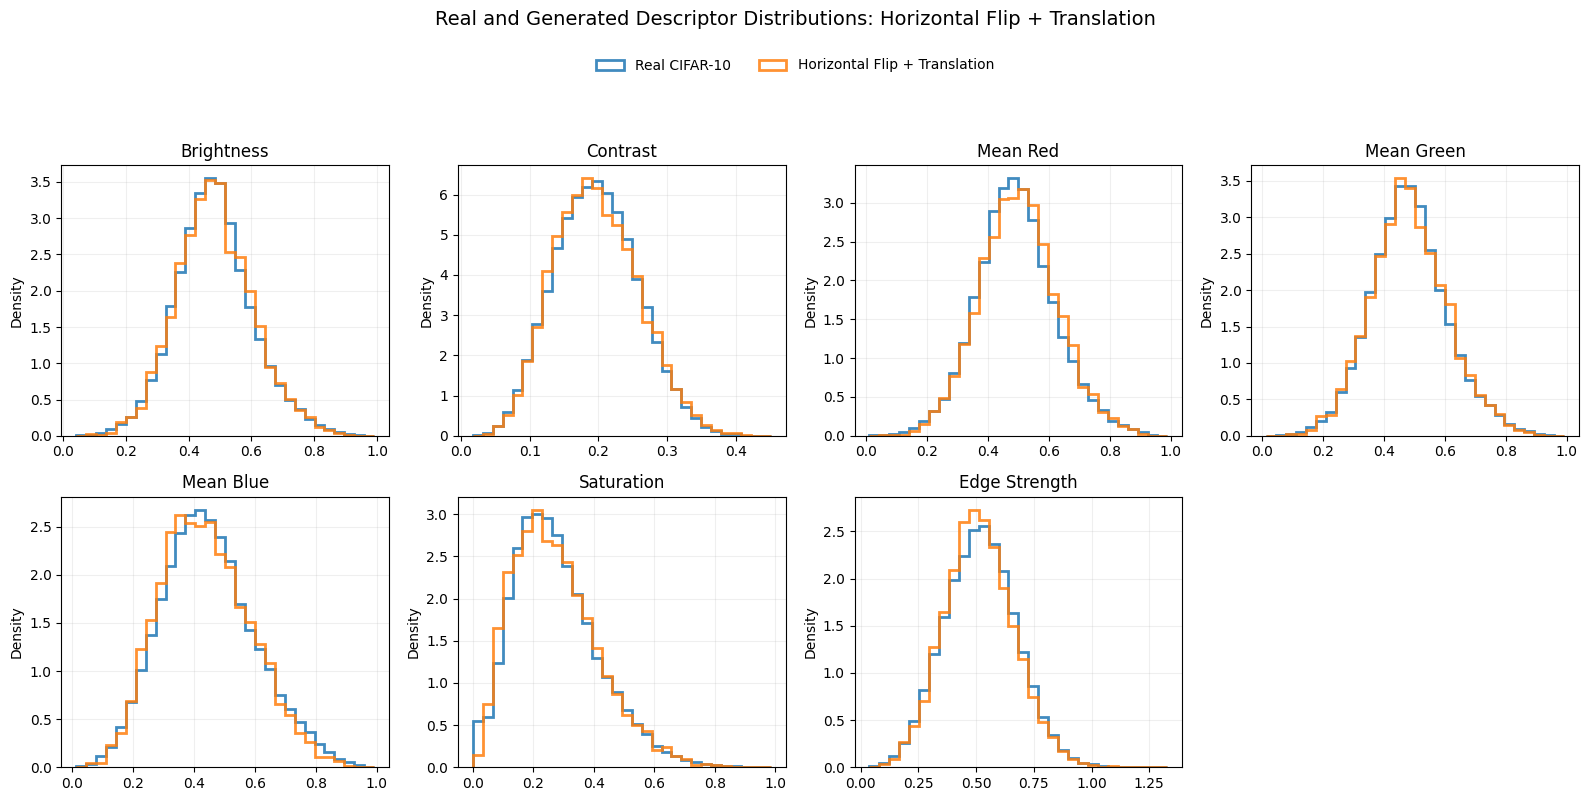

Reference descriptor plot saved: [local project directory]/grids/augmentation_tier2_reference_descriptor_distributions.png
Candidate descriptor plot saved: [local project directory]/grids/augmentation_tier2_fliptranslation_descriptor_distributions.png
Protected test set remains unused.


In [91]:
required_augmentation_descriptor_plot_objects = [
    "augmentation_reference_descriptors",
    "augmentation_candidate_descriptors",
    "plot_descriptor_distributions",
    "real_descriptor_df",
    "GRIDS_DIR",
]

missing_augmentation_descriptor_plot_objects = [
    name
    for name in required_augmentation_descriptor_plot_objects
    if name not in globals()
]

assert not missing_augmentation_descriptor_plot_objects, (
    "Incomplete augmentation descriptor-plot setup:\n"
    + "\n".join(
        missing_augmentation_descriptor_plot_objects
    )
)


AUGMENTATION_REFERENCE_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / "augmentation_tier2_reference_descriptor_distributions.png"
)

AUGMENTATION_CANDIDATE_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / "augmentation_tier2_fliptranslation_descriptor_distributions.png"
)


plot_descriptor_distributions(
    real_descriptor_df,
    augmentation_reference_descriptors,
    "Reference DCGAN",
    AUGMENTATION_REFERENCE_DESCRIPTOR_PLOT_PATH,
    bin_count=30,
)

plot_descriptor_distributions(
    real_descriptor_df,
    augmentation_candidate_descriptors,
    "Horizontal Flip + Translation",
    AUGMENTATION_CANDIDATE_DESCRIPTOR_PLOT_PATH,
    bin_count=30,
)


print(
    "Reference descriptor plot saved:",
    AUGMENTATION_REFERENCE_DESCRIPTOR_PLOT_PATH,
)

print(
    "Candidate descriptor plot saved:",
    AUGMENTATION_CANDIDATE_DESCRIPTOR_PLOT_PATH,
)

print("Protected test set remains unused.")

In [92]:
required_augmentation_descriptor_closeness_objects = [
    "augmentation_reference_descriptor_comparison_df",
    "augmentation_candidate_descriptor_comparison_df",
    "DESCRIPTOR_COLUMNS",
    "HISTORIES_DIR",
]

missing_augmentation_descriptor_closeness_objects = [
    name
    for name in required_augmentation_descriptor_closeness_objects
    if name not in globals()
]

assert not missing_augmentation_descriptor_closeness_objects, (
    "Incomplete descriptor-closeness setup:\n"
    + "\n".join(
        missing_augmentation_descriptor_closeness_objects
    )
)


reference_mean_errors = (
    augmentation_reference_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)

candidate_mean_errors = (
    augmentation_candidate_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)


reference_variation_errors = np.abs(
    augmentation_reference_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)

candidate_variation_errors = np.abs(
    augmentation_candidate_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)


mean_ties = np.isclose(
    reference_mean_errors,
    candidate_mean_errors,
    atol=1e-12,
    rtol=0.0,
)

variation_ties = np.isclose(
    reference_variation_errors,
    candidate_variation_errors,
    atol=1e-12,
    rtol=0.0,
)


mean_closer_labels = np.where(
    mean_ties,
    "Tie",
    np.where(
        candidate_mean_errors
        < reference_mean_errors,
        "Flip + Translation",
        "Reference DCGAN",
    ),
)

variation_closer_labels = np.where(
    variation_ties,
    "Tie",
    np.where(
        candidate_variation_errors
        < reference_variation_errors,
        "Flip + Translation",
        "Reference DCGAN",
    ),
)


augmentation_descriptor_closeness_df = pd.DataFrame(
    {
        "Descriptor": DESCRIPTOR_COLUMNS,
        "Reference mean error": reference_mean_errors,
        "Candidate mean error": candidate_mean_errors,
        "Reference variation error": (
            reference_variation_errors
        ),
        "Candidate variation error": (
            candidate_variation_errors
        ),
        "Mean closer to real": mean_closer_labels,
        "Variation closer to real": (
            variation_closer_labels
        ),
    }
)


AUGMENTATION_DESCRIPTOR_CLOSENESS_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_descriptor_closeness.csv"
)

augmentation_descriptor_closeness_df.to_csv(
    AUGMENTATION_DESCRIPTOR_CLOSENESS_PATH,
    index=False,
)


display(
    augmentation_descriptor_closeness_df.round(4)
)


for evidence_column in [
    "Mean closer to real",
    "Variation closer to real",
]:
    print(evidence_column)

    print(
        augmentation_descriptor_closeness_df[
            evidence_column
        ].value_counts()
    )


print(
    "Descriptor closeness saved:",
    AUGMENTATION_DESCRIPTOR_CLOSENESS_PATH,
)

print(
    "The existing 5,000-image pools were reused."
)

print("Protected test set remains unused.")

,Descriptor,Reference mean error,Candidate mean error,Reference variation error,Candidate variation error,Mean closer to real,Variation closer to real
0,Brightness,0.0169,0.0010,0.0525,0.0097,Flip + Translation,Flip + Translation
1,Contrast,0.0012,0.0002,0.0259,0.0159,Flip + Translation,Flip + Translation
2,Mean Red,0.0141,0.0076,0.0383,0.0113,Flip + Translation,Flip + Translation
3,Mean Green,0.0168,0.0002,0.0553,0.0069,Flip + Translation,Flip + Translation
4,Mean Blue,0.0256,0.0104,0.0203,0.0393,Flip + Translation,Reference DCGAN
5,Saturation,0.0026,0.0009,0.0298,0.0099,Flip + Translation,Flip + Translation
6,Edge Strength,0.0102,0.0048,0.0362,0.0353,Flip + Translation,Flip + Translation


Mean closer to real
Mean closer to real
Flip + Translation    7
Name: count, dtype: int64
Variation closer to real
Variation closer to real
Flip + Translation    6
Reference DCGAN       1
Name: count, dtype: int64
Descriptor closeness saved: [local project directory]/histories/augmentation_tier2_descriptor_closeness.csv
The existing 5,000-image pools were reused.
Protected test set remains unused.


#### Descriptor Interpretation

The flip-plus-translation candidate aligned more closely with the real CIFAR-10 training distribution across nearly every low-level descriptor.

For descriptor means, the candidate was closer to the real reference for all seven measured properties:

- brightness;
- contrast;
- mean red;
- mean green;
- mean blue;
- saturation;
- edge strength.

The largest improvements occurred for brightness, mean green and mean blue. For example, the brightness mean error decreased from `0.0169` to `0.0010`, while the mean-green error decreased from `0.0168` to `0.0002`.

For descriptor variation, the candidate was closer to the real standard deviation for six of seven properties. The only exception was mean blue, where the reference standard-deviation ratio of `1.0203` was closer to `1.0` than the candidate ratio of `0.9607`.

The density-normalised distributions also show substantial overlap between the candidate and the real training reference. There is no clear evidence that augmentation caused severe compression, exaggerated variation or an abnormal photometric shift.

Descriptor evidence therefore provides strong supporting evidence in favour of flip-plus-translation augmentation. However, these measurements describe low-level colour, intensity and edge statistics rather than semantic correctness. They must be considered together with FID, manual recognisability, classifier coverage and the remaining diversity and repetition safeguards.

No augmentation setting has yet been adopted.

### 11.10 Diversity and Repetition

The reference DCGAN and flip-plus-translation candidate are compared for generated-to-generated diversity and repetition.

The same 5,000-image evaluation pools from Section 11.8 are reused. InceptionV3 features are extracted once for both pools, after which ten matched random subsets of 1,000 generated images are evaluated against independently sampled real CIFAR-10 training subsets.

For every repeat, the analysis reports:

- mean and median pairwise cosine distance;
- median and minimum nearest-neighbour distance;
- generated-to-real diversity ratio;
- near-duplicate rate using the corresponding real subset's first-percentile nearest-neighbour distance as the threshold.

The same generated subset indices are used for both models within each repeat, enabling a paired comparison. Exact pixel duplicates are separately checked across each complete 5,000-image pool.

This measures generated-to-generated diversity and possible mode collapse. It is not the formal generated-to-training memorisation audit, which remains reserved for Notebook 4.

In [94]:
required_augmentation_diversity_objects = [
    "SECTION6_DIVERSITY_HELPER_READY",
    "compact_cosine_diversity_summary",
    "extract_inception_features",
    "fid_feature_extractor",
    "real_fid_features",
    "FID_FEATURE_DIM",
    "FID_BATCH_SIZE",
    "SELECTED_EVALUATION_SAMPLE_COUNT",
    "DIVERSITY_SUBSET_SIZE",
    "DIVERSITY_REPEATS",
    "REAL_DIVERSITY_SEED",
    "GENERATED_DIVERSITY_SEED",
    "NEAR_DUPLICATE_PERCENTILE",
    "augmentation_reference_evaluation_images",
    "augmentation_candidate_evaluation_images",
    "HISTORIES_DIR",
]

missing_augmentation_diversity_objects = [
    name
    for name in required_augmentation_diversity_objects
    if name not in globals()
]

assert not missing_augmentation_diversity_objects, (
    "Incomplete augmentation diversity setup:\n"
    + "\n".join(
        missing_augmentation_diversity_objects
    )
)


assert SECTION6_DIVERSITY_HELPER_READY

assert callable(
    compact_cosine_diversity_summary
)

assert SELECTED_EVALUATION_SAMPLE_COUNT == 5_000
assert DIVERSITY_SUBSET_SIZE == 1_000
assert DIVERSITY_REPEATS == 10

assert REAL_DIVERSITY_SEED == 1301
assert GENERATED_DIVERSITY_SEED == 1302

assert NEAR_DUPLICATE_PERCENTILE == 1.0


for image_pool in [
    augmentation_reference_evaluation_images,
    augmentation_candidate_evaluation_images,
]:
    assert image_pool.shape == (
        SELECTED_EVALUATION_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert image_pool.dtype == np.uint8


augmentation_reference_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            augmentation_reference_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )
)

augmentation_candidate_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            augmentation_candidate_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FID_BATCH_SIZE,
    )
)


for feature_pool in [
    augmentation_reference_evaluation_features,
    augmentation_candidate_evaluation_features,
]:
    assert feature_pool.shape == (
        SELECTED_EVALUATION_SAMPLE_COUNT,
        FID_FEATURE_DIM,
    )

    assert np.isfinite(
        feature_pool
    ).all()


print(
    "Augmentation diversity feature pools ready."
)

print(
    "Reference features:",
    augmentation_reference_evaluation_features.shape,
)

print(
    "Candidate features:",
    augmentation_candidate_evaluation_features.shape,
)

print(
    "Generated image pools were reused."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Augmentation diversity feature pools ready.
Reference features: (5000, 2048)
Candidate features: (5000, 2048)
Generated image pools were reused.
Protected test set remains unused.


In [95]:
augmentation_real_diversity_rng = (
    np.random.default_rng(
        REAL_DIVERSITY_SEED
    )
)

augmentation_generated_diversity_rng = (
    np.random.default_rng(
        GENERATED_DIVERSITY_SEED
    )
)


augmentation_diversity_repeat_rows = []

# Retain repeat 1 for the later nearest-neighbour
# ECDF and closest-pair visual inspection.
augmentation_diversity_representative = None


for repeat_index in range(
    1,
    DIVERSITY_REPEATS + 1,
):
    real_indices = (
        augmentation_real_diversity_rng.choice(
            len(real_fid_features),
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        augmentation_generated_diversity_rng.choice(
            SELECTED_EVALUATION_SAMPLE_COUNT,
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )


    real_summary = (
        compact_cosine_diversity_summary(
            real_fid_features[
                real_indices
            ]
        )
    )

    reference_summary = (
        compact_cosine_diversity_summary(
            augmentation_reference_evaluation_features[
                generated_indices
            ]
        )
    )

    candidate_summary = (
        compact_cosine_diversity_summary(
            augmentation_candidate_evaluation_features[
                generated_indices
            ]
        )
    )


    near_duplicate_threshold = float(
        np.percentile(
            real_summary[
                "nearest_distances"
            ],
            NEAR_DUPLICATE_PERCENTILE,
        )
    )


    repeat_summaries = {
        "Real CIFAR-10": real_summary,
        "Reference DCGAN": reference_summary,
        "Horizontal flip + translation": (
            candidate_summary
        ),
    }


    for configuration, summary in (
        repeat_summaries.items()
    ):
        if configuration == "Real CIFAR-10":
            diversity_ratio = 1.0

        else:
            diversity_ratio = float(
                summary[
                    "mean_pairwise_distance"
                ]
                / real_summary[
                    "mean_pairwise_distance"
                ]
            )


        near_duplicate_rate = float(
            np.mean(
                summary[
                    "nearest_distances"
                ]
                < near_duplicate_threshold
            )
            * 100.0
        )


        augmentation_diversity_repeat_rows.append(
            {
                "Repeat": repeat_index,
                "Configuration": configuration,
                "Feature sample count": (
                    DIVERSITY_SUBSET_SIZE
                ),
                "Mean pairwise distance": (
                    summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Median pairwise distance": (
                    summary[
                        "median_pairwise_distance"
                    ]
                ),
                "Median nearest distance": (
                    summary[
                        "median_nearest_distance"
                    ]
                ),
                "Minimum nearest distance": (
                    summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-duplicate threshold": (
                    near_duplicate_threshold
                ),
                "Near-duplicate rate (%)": (
                    near_duplicate_rate
                ),
                "Diversity ratio to real": (
                    diversity_ratio
                ),
            }
        )


    if repeat_index == 1:
        augmentation_diversity_representative = {
            "generated_indices": (
                generated_indices.copy()
            ),
            "real_nearest_distances": (
                real_summary[
                    "nearest_distances"
                ].copy()
            ),
            "reference_nearest_distances": (
                reference_summary[
                    "nearest_distances"
                ].copy()
            ),
            "candidate_nearest_distances": (
                candidate_summary[
                    "nearest_distances"
                ].copy()
            ),
            "near_duplicate_threshold": (
                near_duplicate_threshold
            ),
        }


augmentation_diversity_repeats_df = (
    pd.DataFrame(
        augmentation_diversity_repeat_rows
    )
)


assert len(
    augmentation_diversity_repeats_df
) == DIVERSITY_REPEATS * 3

assert (
    augmentation_diversity_repeats_df[
        "Repeat"
    ].nunique()
    == DIVERSITY_REPEATS
)

assert augmentation_diversity_representative is not None


print(
    "Completed matched diversity repeats:",
    DIVERSITY_REPEATS,
)

print(
    "Repeat-level rows:",
    len(augmentation_diversity_repeats_df),
)

print("Protected test set remains unused.")

Completed matched diversity repeats: 10
Repeat-level rows: 30
Protected test set remains unused.


In [96]:
augmentation_diversity_summary_df = (
    augmentation_diversity_repeats_df
    .groupby(
        "Configuration",
        as_index=False,
    )
    .agg(
        mean_pairwise_distance_mean=(
            "Mean pairwise distance",
            "mean",
        ),
        mean_pairwise_distance_sd=(
            "Mean pairwise distance",
            "std",
        ),
        median_pairwise_distance_mean=(
            "Median pairwise distance",
            "mean",
        ),
        median_nearest_distance_mean=(
            "Median nearest distance",
            "mean",
        ),
        minimum_nearest_distance_mean=(
            "Minimum nearest distance",
            "mean",
        ),
        near_duplicate_rate_mean=(
            "Near-duplicate rate (%)",
            "mean",
        ),
        near_duplicate_rate_sd=(
            "Near-duplicate rate (%)",
            "std",
        ),
        diversity_ratio_mean=(
            "Diversity ratio to real",
            "mean",
        ),
        diversity_ratio_sd=(
            "Diversity ratio to real",
            "std",
        ),
    )
)


AUGMENTATION_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_diversity_repeats.csv"
)

AUGMENTATION_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_diversity_summary.csv"
)


augmentation_diversity_repeats_df.to_csv(
    AUGMENTATION_DIVERSITY_REPEATS_PATH,
    index=False,
)

augmentation_diversity_summary_df.to_csv(
    AUGMENTATION_DIVERSITY_SUMMARY_PATH,
    index=False,
)


reference_diversity_rows = (
    augmentation_diversity_repeats_df.loc[
        augmentation_diversity_repeats_df[
            "Configuration"
        ]
        == "Reference DCGAN"
    ]
    .sort_values("Repeat")
)

candidate_diversity_rows = (
    augmentation_diversity_repeats_df.loc[
        augmentation_diversity_repeats_df[
            "Configuration"
        ]
        == "Horizontal flip + translation"
    ]
    .sort_values("Repeat")
)


reference_diversity_ratios = (
    reference_diversity_rows[
        "Diversity ratio to real"
    ].to_numpy(dtype=np.float64)
)

candidate_diversity_ratios = (
    candidate_diversity_rows[
        "Diversity ratio to real"
    ].to_numpy(dtype=np.float64)
)


candidate_ratio_advantages = (
    np.abs(
        reference_diversity_ratios - 1.0
    )
    - np.abs(
        candidate_diversity_ratios - 1.0
    )
)


reference_near_duplicate_rates = (
    reference_diversity_rows[
        "Near-duplicate rate (%)"
    ].to_numpy(dtype=np.float64)
)

candidate_near_duplicate_rates = (
    candidate_diversity_rows[
        "Near-duplicate rate (%)"
    ].to_numpy(dtype=np.float64)
)


display(
    augmentation_diversity_summary_df.round(6)
)


print(
    "Repeats where candidate diversity ratio "
    "was closer to real:",
    int(
        np.sum(
            candidate_ratio_advantages > 0
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Mean candidate improvement in absolute "
    "diversity-ratio error:",
    f"{candidate_ratio_advantages.mean():.6f}",
)

print(
    "Repeats where candidate had a lower "
    "near-duplicate rate:",
    int(
        np.sum(
            candidate_near_duplicate_rates
            < reference_near_duplicate_rates
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Repeats where near-duplicate rates tied:",
    int(
        np.sum(
            np.isclose(
                candidate_near_duplicate_rates,
                reference_near_duplicate_rates,
                atol=1e-12,
                rtol=0.0,
            )
        )
    ),
    "of",
    DIVERSITY_REPEATS,
)

print(
    "Repeat-level results saved:",
    AUGMENTATION_DIVERSITY_REPEATS_PATH,
)

print(
    "Diversity summary saved:",
    AUGMENTATION_DIVERSITY_SUMMARY_PATH,
)

print("Protected test set remains unused.")

,Configuration,mean_pairwise_distance_mean,mean_pairwise_distance_sd,median_pairwise_distance_mean,median_nearest_distance_mean,minimum_nearest_distance_mean,near_duplicate_rate_mean,near_duplicate_rate_sd,diversity_ratio_mean,diversity_ratio_sd
0,Horizontal flip + translation,0.358178,0.001085,0.356411,0.201647,0.113052,0.00,0.00000,0.952219,0.007489
1,Real CIFAR-10,0.376167,0.002501,0.378124,0.195888,0.061053,0.96,0.05164,1.000000,0.000000
2,Reference DCGAN,0.351328,0.001756,0.349983,0.196041,0.119539,0.00,0.00000,0.934004,0.007671


Repeats where candidate diversity ratio was closer to real: 10 of 10
Mean candidate improvement in absolute diversity-ratio error: 0.018215
Repeats where candidate had a lower near-duplicate rate: 0 of 10
Repeats where near-duplicate rates tied: 10 of 10
Repeat-level results saved: [local project directory]/histories/augmentation_tier2_diversity_repeats.csv
Diversity summary saved: [local project directory]/histories/augmentation_tier2_diversity_summary.csv
Protected test set remains unused.


In [97]:
augmentation_reference_flat_images = (
    augmentation_reference_evaluation_images.reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

augmentation_candidate_flat_images = (
    augmentation_candidate_evaluation_images.reshape(
        SELECTED_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)


augmentation_reference_unique_count = int(
    np.unique(
        augmentation_reference_flat_images,
        axis=0,
    ).shape[0]
)

augmentation_candidate_unique_count = int(
    np.unique(
        augmentation_candidate_flat_images,
        axis=0,
    ).shape[0]
)


augmentation_reference_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - augmentation_reference_unique_count
)

augmentation_candidate_exact_duplicates = int(
    SELECTED_EVALUATION_SAMPLE_COUNT
    - augmentation_candidate_unique_count
)


augmentation_exact_duplicate_df = pd.DataFrame(
    [
        {
            "Configuration": "Reference DCGAN",
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Unique images": (
                augmentation_reference_unique_count
            ),
            "Exact duplicates": (
                augmentation_reference_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                augmentation_reference_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
        {
            "Configuration": (
                "Horizontal flip + translation"
            ),
            "Image sample count": (
                SELECTED_EVALUATION_SAMPLE_COUNT
            ),
            "Unique images": (
                augmentation_candidate_unique_count
            ),
            "Exact duplicates": (
                augmentation_candidate_exact_duplicates
            ),
            "Exact-duplicate rate (%)": (
                augmentation_candidate_exact_duplicates
                / SELECTED_EVALUATION_SAMPLE_COUNT
                * 100.0
            ),
        },
    ]
)


AUGMENTATION_EXACT_DUPLICATE_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_exact_duplicates.csv"
)

augmentation_exact_duplicate_df.to_csv(
    AUGMENTATION_EXACT_DUPLICATE_PATH,
    index=False,
)


display(
    augmentation_exact_duplicate_df.round(6)
)


print(
    "Exact-duplicate results saved:",
    AUGMENTATION_EXACT_DUPLICATE_PATH,
)

print(
    "No generated-to-training "
    "memorisation audit was performed."
)

print("Protected test set remains unused.")


del augmentation_reference_flat_images
del augmentation_candidate_flat_images

gc.collect()

,Configuration,Image sample count,Unique images,Exact duplicates,Exact-duplicate rate (%)
0,Reference DCGAN,5000,5000,0,0.0
1,Horizontal flip + translation,5000,5000,0,0.0


Exact-duplicate results saved: [local project directory]/histories/augmentation_tier2_exact_duplicates.csv
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


0

#### Nearest-Neighbour Distance and Closest-Pair Inspection

The first matched diversity repeat is retained for visual inspection.

The nearest-neighbour distance distributions are compared using empirical cumulative distribution functions. This reveals whether summary statistics hide a broader shift toward tightly clustered generated features.

The ten closest unique generated-image pairs from each model are also displayed. These panels help determine whether small feature-space distances represent:

- almost identical outputs;
- repeated colour or texture templates;
- similar object poses or layouts;
- visually distinct images that the feature extractor places nearby.

This remains a generated-to-generated repetition analysis. It is not a generated-to-training memorisation audit.

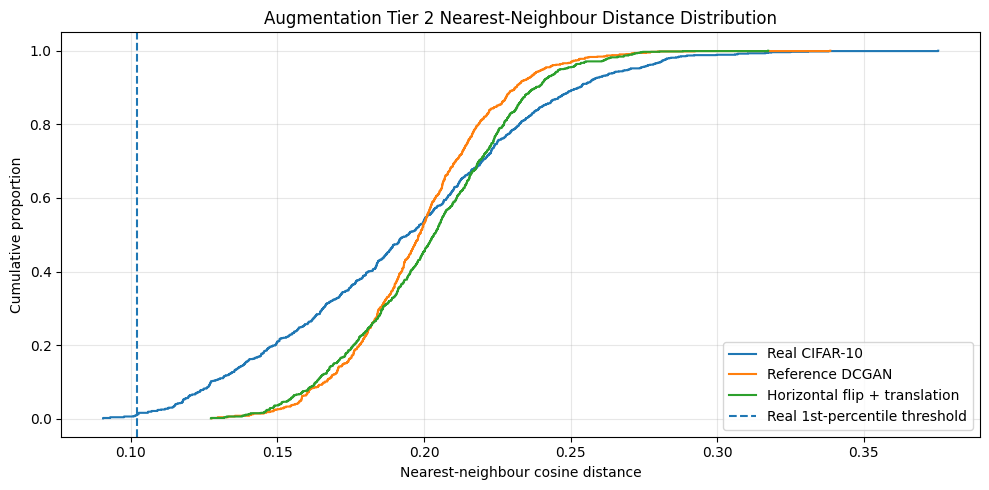

Nearest-distance plot saved: [local project directory]/grids/augmentation_tier2_nearest_distance_ecdf.png
Near-duplicate threshold: 0.102203
Protected test set remains unused.


In [99]:
required_augmentation_nearest_distance_objects = [
    "augmentation_diversity_representative",
    "GRIDS_DIR",
]

missing_augmentation_nearest_distance_objects = [
    name
    for name in required_augmentation_nearest_distance_objects
    if name not in globals()
]

assert not missing_augmentation_nearest_distance_objects, (
    "Incomplete nearest-distance setup:\n"
    + "\n".join(
        missing_augmentation_nearest_distance_objects
    )
)


augmentation_real_nearest_distances = np.asarray(
    augmentation_diversity_representative[
        "real_nearest_distances"
    ],
    dtype=np.float64,
)

augmentation_reference_nearest_distances = np.asarray(
    augmentation_diversity_representative[
        "reference_nearest_distances"
    ],
    dtype=np.float64,
)

augmentation_candidate_nearest_distances = np.asarray(
    augmentation_diversity_representative[
        "candidate_nearest_distances"
    ],
    dtype=np.float64,
)

augmentation_near_duplicate_threshold = float(
    augmentation_diversity_representative[
        "near_duplicate_threshold"
    ]
)


for nearest_distances in [
    augmentation_real_nearest_distances,
    augmentation_reference_nearest_distances,
    augmentation_candidate_nearest_distances,
]:
    assert nearest_distances.shape == (
        DIVERSITY_SUBSET_SIZE,
    )

    assert np.isfinite(
        nearest_distances
    ).all()


AUGMENTATION_NEAREST_DISTANCE_PLOT_PATH = (
    GRIDS_DIR
    / "augmentation_tier2_nearest_distance_ecdf.png"
)


plt.figure(
    figsize=(10, 5)
)


for distances, label in [
    (
        augmentation_real_nearest_distances,
        "Real CIFAR-10",
    ),
    (
        augmentation_reference_nearest_distances,
        "Reference DCGAN",
    ),
    (
        augmentation_candidate_nearest_distances,
        "Horizontal flip + translation",
    ),
]:
    sorted_distances = np.sort(
        distances
    )

    ecdf = np.arange(
        1,
        len(sorted_distances) + 1,
    ) / len(sorted_distances)

    plt.step(
        sorted_distances,
        ecdf,
        where="post",
        label=label,
    )


plt.axvline(
    augmentation_near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "Augmentation Tier 2 "
    "Nearest-Neighbour Distance Distribution"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    AUGMENTATION_NEAREST_DISTANCE_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Nearest-distance plot saved:",
    AUGMENTATION_NEAREST_DISTANCE_PLOT_PATH,
)

print(
    "Near-duplicate threshold:",
    f"{augmentation_near_duplicate_threshold:.6f}",
)

print(
    "Protected test set remains unused."
)

In [100]:
required_augmentation_closest_pair_objects = [
    "augmentation_diversity_representative",
    "augmentation_reference_evaluation_features",
    "augmentation_candidate_evaluation_features",
    "augmentation_reference_evaluation_images",
    "augmentation_candidate_evaluation_images",
    "DIVERSITY_SUBSET_SIZE",
    "HISTORIES_DIR",
]

missing_augmentation_closest_pair_objects = [
    name
    for name in required_augmentation_closest_pair_objects
    if name not in globals()
]

assert not missing_augmentation_closest_pair_objects, (
    "Incomplete closest-pair setup:\n"
    + "\n".join(
        missing_augmentation_closest_pair_objects
    )
)


augmentation_pair_subset_indices = np.asarray(
    augmentation_diversity_representative[
        "generated_indices"
    ],
    dtype=np.int64,
)


assert augmentation_pair_subset_indices.shape == (
    DIVERSITY_SUBSET_SIZE,
)

assert len(
    np.unique(
        augmentation_pair_subset_indices
    )
) == DIVERSITY_SUBSET_SIZE


augmentation_closest_pair_rows = []

augmentation_closest_pair_results = {}


for configuration, feature_pool in [
    (
        "Reference DCGAN",
        augmentation_reference_evaluation_features,
    ),
    (
        "Horizontal flip + translation",
        augmentation_candidate_evaluation_features,
    ),
]:
    subset_features = feature_pool[
        augmentation_pair_subset_indices
    ].astype(
        np.float32
    )

    feature_norms = np.linalg.norm(
        subset_features,
        axis=1,
        keepdims=True,
    )

    normalised_features = (
        subset_features
        / np.maximum(
            feature_norms,
            1e-12,
        )
    )

    distance_matrix = np.clip(
        1.0
        - (
            normalised_features
            @ normalised_features.T
        ),
        0.0,
        2.0,
    )

    np.fill_diagonal(
        distance_matrix,
        np.inf,
    )


    nearest_indices = np.argmin(
        distance_matrix,
        axis=1,
    )

    unique_pair_distances = {}


    for first_index, second_index in enumerate(
        nearest_indices
    ):
        pair = tuple(
            sorted(
                (
                    int(first_index),
                    int(second_index),
                )
            )
        )

        pair_distance = float(
            distance_matrix[
                first_index,
                second_index,
            ]
        )

        if (
            pair not in unique_pair_distances
            or pair_distance
            < unique_pair_distances[pair]
        ):
            unique_pair_distances[
                pair
            ] = pair_distance


    closest_pairs = sorted(
        unique_pair_distances.items(),
        key=lambda item: item[1],
    )[:10]


    assert len(closest_pairs) == 10


    augmentation_closest_pair_results[
        configuration
    ] = closest_pairs


    for pair_number, (
        (
            first_subset_index,
            second_subset_index,
        ),
        cosine_distance,
    ) in enumerate(
        closest_pairs,
        start=1,
    ):
        augmentation_closest_pair_rows.append(
            {
                "Configuration": configuration,
                "Pair": pair_number,
                "First subset index": (
                    first_subset_index
                ),
                "Second subset index": (
                    second_subset_index
                ),
                "First pool index": int(
                    augmentation_pair_subset_indices[
                        first_subset_index
                    ]
                ),
                "Second pool index": int(
                    augmentation_pair_subset_indices[
                        second_subset_index
                    ]
                ),
                "Cosine distance": (
                    cosine_distance
                ),
            }
        )


augmentation_closest_pairs_df = pd.DataFrame(
    augmentation_closest_pair_rows
)


assert len(
    augmentation_closest_pairs_df
) == 20


AUGMENTATION_CLOSEST_PAIRS_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_closest_generated_pairs.csv"
)

augmentation_closest_pairs_df.to_csv(
    AUGMENTATION_CLOSEST_PAIRS_PATH,
    index=False,
)


display(
    augmentation_closest_pairs_df.round(6)
)


print(
    "Closest-pair table saved:",
    AUGMENTATION_CLOSEST_PAIRS_PATH,
)

print(
    "Matched first-repeat subset retained."
)

print(
    "Protected test set remains unused."
)

,Configuration,Pair,First subset index,Second subset index,First pool index,Second pool index,Cosine distance
0,Reference DCGAN,1,75,424,2497,1704,0.127625
1,Reference DCGAN,2,655,731,3531,145,0.129681
2,Reference DCGAN,3,268,688,2122,821,0.133227
3,Reference DCGAN,4,825,951,4238,3101,0.135524
4,Reference DCGAN,5,471,764,4793,3112,0.140402
5,Reference DCGAN,6,181,925,2459,927,0.141034
6,Reference DCGAN,7,393,968,666,3155,0.141765
7,Reference DCGAN,8,123,832,2495,901,0.145418
8,Reference DCGAN,9,778,917,2748,2106,0.146226
9,Reference DCGAN,10,108,123,1457,2495,0.147419


Closest-pair table saved: [local project directory]/histories/augmentation_tier2_closest_generated_pairs.csv
Matched first-repeat subset retained.
Protected test set remains unused.


In [101]:
augmentation_closest_pair_plot_specs = [
    {
        "Configuration": "Reference DCGAN",
        "Images": (
            augmentation_reference_evaluation_images
        ),
        "Output path": (
            GRIDS_DIR
            / (
                "augmentation_tier2_reference_"
                "closest_generated_pairs.png"
            )
        ),
    },
    {
        "Configuration": (
            "Horizontal flip + translation"
        ),
        "Images": (
            augmentation_candidate_evaluation_images
        ),
        "Output path": (
            GRIDS_DIR
            / (
                "augmentation_tier2_fliptranslation_"
                "closest_generated_pairs.png"
            )
        ),
    },
]


for plot_specification in (
    augmentation_closest_pair_plot_specs
):
    configuration = plot_specification[
        "Configuration"
    ]

    image_pool = plot_specification[
        "Images"
    ]

    output_path = plot_specification[
        "Output path"
    ]

    closest_pairs = (
        augmentation_closest_pair_results[
            configuration
        ]
    )


    figure, axes = plt.subplots(
        5,
        4,
        figsize=(12, 15),
    )


    for pair_offset, (
        (
            first_subset_index,
            second_subset_index,
        ),
        cosine_distance,
    ) in enumerate(
        closest_pairs
    ):
        row_index = pair_offset // 2

        pair_column = (
            pair_offset % 2
        ) * 2

        first_pool_index = int(
            augmentation_pair_subset_indices[
                first_subset_index
            ]
        )

        second_pool_index = int(
            augmentation_pair_subset_indices[
                second_subset_index
            ]
        )


        first_axis = axes[
            row_index,
            pair_column,
        ]

        second_axis = axes[
            row_index,
            pair_column + 1,
        ]


        first_axis.imshow(
            image_pool[
                first_pool_index
            ]
        )

        second_axis.imshow(
            image_pool[
                second_pool_index
            ]
        )


        pair_number = pair_offset + 1

        first_axis.set_title(
            f"Pair {pair_number}A",
            fontsize=10,
        )

        second_axis.set_title(
            (
                f"Pair {pair_number}B\n"
                f"Distance: {cosine_distance:.4f}"
            ),
            fontsize=10,
        )


        first_axis.axis("off")
        second_axis.axis("off")


    figure.suptitle(
        (
            f"{configuration} "
            "Most Similar Generated Pairs"
        ),
        fontsize=16,
    )

    figure.tight_layout(
        rect=(0, 0, 1, 0.97)
    )

    figure.savefig(
        output_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


    print(
        f"{configuration} closest-pair panel saved:",
        output_path,
    )


print(
    "No generated-to-training "
    "memorisation audit was performed."
)

print(
    "Protected test set remains unused."
)

Reference DCGAN closest-pair panel saved: [local project directory]/grids/augmentation_tier2_reference_closest_generated_pairs.png


Horizontal flip + translation closest-pair panel saved: [local project directory]/grids/augmentation_tier2_fliptranslation_closest_generated_pairs.png
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


#### Diversity and Repetition Interpretation

The flip-plus-translation candidate retained more feature-space diversity than the reference DCGAN.

Its mean generated-to-real diversity ratio was `0.9522`, compared with `0.9340` for the reference. The candidate's ratio was closer to the real-image value of `1.0` in all ten matched repeats, with a mean reduction of `0.0182` in absolute diversity-ratio error.

The nearest-neighbour distance distribution supports the same direction. The candidate distribution is generally shifted toward slightly larger distances than the reference, indicating less tightly clustered generated features.

Neither generated model triggered the near-duplicate safeguard:

- mean near-duplicate rate: `0.00%` for both models;
- exact duplicates among 5,000 images: `0` for both models.

The candidate had a slightly lower mean minimum nearest-neighbour distance, `0.1131` compared with `0.1195`, but this remained above the real first-percentile near-duplicate threshold and did not produce any detected near duplicates.

The closest-pair panels contain recurring object themes, particularly vehicles, but the paired images remain visually distinct rather than being copies. Some images appear in more than one nearest-neighbour relationship, indicating small local clusters of similar outputs rather than exact duplication or broad mode collapse.

Diversity and repetition evidence therefore favours flip-plus-translation augmentation. It improves overall feature-space spread while passing both near-duplicate and exact-duplicate safeguards.

This analysis concerns generated-to-generated repetition only. No generated-to-training memorisation audit was performed.

### 11.11 Stability and Compute Consolidation

The selected reference and augmentation candidate are compared using their complete saved training histories.

The consolidation reports:

- complete training trajectories;
- final-20 generator and discriminator loss variation;
- mean real-image and generated-image discriminator scores;
- discriminator score separation during epochs 61–80 and 81–100;
- change in late-training score separation;
- total training time;
- matched parameter counts and update exposure.

Losses and discriminator scores diagnose adversarial balance and numerical stability. They are not used as direct image-quality measurements.

In [103]:
required_augmentation_stability_plot_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_augmentation_stability_plot_objects = [
    name
    for name in required_augmentation_stability_plot_objects
    if name not in globals()
]

assert not missing_augmentation_stability_plot_objects, (
    "Incomplete augmentation stability-plot setup:\n"
    + "\n".join(
        missing_augmentation_stability_plot_objects
    )
)


augmentation_tier2_history_specs = [
    {
        "label": "Reference DCGAN",
        "history_path": (
            HISTORIES_DIR
            / f"{AUGMENTATION_REFERENCE_RUN_ID}.csv"
        ),
    },
    {
        "label": (
            "Horizontal flip + translation"
        ),
        "history_path": (
            HISTORIES_DIR
            / (
                f"{AUGMENTATION_TIER2_CANDIDATE_RUN_ID}"
                ".csv"
            )
        ),
    },
]


for history_specification in (
    augmentation_tier2_history_specs
):
    assert history_specification[
        "history_path"
    ].is_file(), (
        "Missing training history:\n"
        f"{history_specification['history_path']}"
    )


AUGMENTATION_TIER2_TRAJECTORY_PATH = (
    GRIDS_DIR
    / "augmentation_tier2_training_trajectories.png"
)


plot_dcgan_history_comparison(
    history_specs=augmentation_tier2_history_specs,
    title=(
        "Augmentation Tier 2 "
        "Training Trajectories"
    ),
    output_path=(
        AUGMENTATION_TIER2_TRAJECTORY_PATH
    ),
)


print(
    "Tier 2 trajectory comparison saved:",
    AUGMENTATION_TIER2_TRAJECTORY_PATH,
)

print(
    "Losses and scores remain diagnostic only."
)

print("Protected test set remains unused.")

Tier 2 trajectory comparison saved: [local project directory]/grids/augmentation_tier2_training_trajectories.png
Losses and scores remain diagnostic only.
Protected test set remains unused.


In [104]:
required_augmentation_stability_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "x_train_gan",
    "HISTORIES_DIR",
]

missing_augmentation_stability_objects = [
    name
    for name in required_augmentation_stability_objects
    if name not in globals()
]

assert not missing_augmentation_stability_objects, (
    "Incomplete augmentation stability setup:\n"
    + "\n".join(
        missing_augmentation_stability_objects
    )
)


AUGMENTATION_TIER2_TARGET_EPOCHS = 100

AUGMENTATION_TIER2_BATCHES_PER_EPOCH = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

AUGMENTATION_TIER2_EXPECTED_UPDATES = (
    AUGMENTATION_TIER2_BATCHES_PER_EPOCH
    * AUGMENTATION_TIER2_TARGET_EPOCHS
)


assert len(x_train_gan) == 50_000
assert CURRENT_BATCH_SIZE == 64

assert AUGMENTATION_TIER2_BATCHES_PER_EPOCH == 782

assert AUGMENTATION_TIER2_EXPECTED_UPDATES == 78_200


augmentation_stability_specs = [
    {
        "Configuration": "Reference DCGAN",
        "Run ID": AUGMENTATION_REFERENCE_RUN_ID,
    },
    {
        "Configuration": (
            "Horizontal flip + translation"
        ),
        "Run ID": (
            AUGMENTATION_TIER2_CANDIDATE_RUN_ID
        ),
    },
]


augmentation_stability_rows = []


for specification in augmentation_stability_specs:
    configuration = specification[
        "Configuration"
    ]

    run_id = specification["Run ID"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    history_df = (
        pd.read_csv(
            history_path
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    required_history_columns = [
        "epoch",
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
        "epoch_time_seconds",
    ]

    missing_history_columns = [
        column
        for column in required_history_columns
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{run_id} history is missing:\n"
        + "\n".join(
            missing_history_columns
        )
    )

    assert len(history_df) == 100

    assert np.isfinite(
        history_df[
            required_history_columns
        ].to_numpy(dtype=np.float64)
    ).all()


    epochs_61_80_df = history_df.loc[
        history_df["epoch"].between(
            61,
            80,
        )
    ]

    final_20_df = history_df.loc[
        history_df["epoch"].between(
            81,
            100,
        )
    ]


    assert len(epochs_61_80_df) == 20
    assert len(final_20_df) == 20


    epochs_61_80_score_separation = (
        epochs_61_80_df["real_score"]
        - epochs_61_80_df["fake_score"]
    )

    final_20_score_separation = (
        final_20_df["real_score"]
        - final_20_df["fake_score"]
    )


    augmentation_stability_rows.append(
        {
            "Configuration": configuration,
            "Run ID": run_id,
            "Generator parameters": (
                CURRENT_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CURRENT_DISCRIMINATOR_PARAMETERS
            ),
            "Generator updates": (
                AUGMENTATION_TIER2_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                AUGMENTATION_TIER2_EXPECTED_UPDATES
            ),
            "Training time minutes": (
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final-20 G loss mean": (
                final_20_df[
                    "generator_loss"
                ].mean()
            ),
            "Final-20 G loss SD": (
                final_20_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Final-20 D loss mean": (
                final_20_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Final-20 D loss SD": (
                final_20_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Final-20 real score mean": (
                final_20_df[
                    "real_score"
                ].mean()
            ),
            "Final-20 fake score mean": (
                final_20_df[
                    "fake_score"
                ].mean()
            ),
            "Epochs 61–80 score separation": (
                epochs_61_80_score_separation.mean()
            ),
            "Final-20 score separation": (
                final_20_score_separation.mean()
            ),
            "Late score-separation change": (
                final_20_score_separation.mean()
                - epochs_61_80_score_separation.mean()
            ),
        }
    )


augmentation_tier2_stability_compute_df = (
    pd.DataFrame(
        augmentation_stability_rows
    )
)


reference_runtime_minutes = float(
    augmentation_tier2_stability_compute_df.loc[
        augmentation_tier2_stability_compute_df[
            "Configuration"
        ]
        == "Reference DCGAN",
        "Training time minutes",
    ].iloc[0]
)

candidate_runtime_minutes = float(
    augmentation_tier2_stability_compute_df.loc[
        augmentation_tier2_stability_compute_df[
            "Configuration"
        ]
        == "Horizontal flip + translation",
        "Training time minutes",
    ].iloc[0]
)


augmentation_runtime_difference_minutes = float(
    candidate_runtime_minutes
    - reference_runtime_minutes
)

augmentation_runtime_difference_percent = float(
    augmentation_runtime_difference_minutes
    / reference_runtime_minutes
    * 100.0
)


AUGMENTATION_TIER2_STABILITY_COMPUTE_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_stability_compute.csv"
)

augmentation_tier2_stability_compute_df.to_csv(
    AUGMENTATION_TIER2_STABILITY_COMPUTE_PATH,
    index=False,
)


display(
    augmentation_tier2_stability_compute_df.round(4)
)


print(
    "Candidate minus reference runtime:",
    f"{augmentation_runtime_difference_minutes:.4f}",
    "minutes",
)

print(
    "Candidate runtime overhead:",
    f"{augmentation_runtime_difference_percent:.2f}%",
)

print(
    "Stability and compute summary saved:",
    AUGMENTATION_TIER2_STABILITY_COMPUTE_PATH,
)

print(
    "No image-quality conclusion is made "
    "from losses or scores alone."
)

print(
    "No augmentation setting has been adopted."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Generator parameters,Discriminator parameters,Generator updates,Discriminator updates,Training time minutes,Final-20 G loss mean,Final-20 G loss SD,Final-20 D loss mean,Final-20 D loss SD,Final-20 real score mean,Final-20 fake score mean,Epochs 61–80 score separation,Final-20 score separation,Late score-separation change
0,Reference DCGAN,G02_dcgan_seed42,1085187,664129,78200,78200,19.4674,4.6590,0.1529,0.1044,0.0217,0.9359,0.0639,0.8453,0.8720,0.0267
1,Horizontal flip + translation,G08_augmentation_fliptranslation_seed42,1085187,664129,78200,78200,22.4793,2.9404,0.1009,0.2166,0.0099,0.8503,0.1495,0.6577,0.7008,0.0431


Candidate minus reference runtime: 3.0119 minutes
Candidate runtime overhead: 15.47%
Stability and compute summary saved: [local project directory]/histories/augmentation_tier2_stability_compute.csv
No image-quality conclusion is made from losses or scores alone.
No augmentation setting has been adopted.
Protected test set remains unused.


### 11.12 Final Augmentation Evidence and Provisional Decision

The complete Tier 2 package now compares the unaugmented reference DCGAN with the strongest augmentation candidate, horizontal flipping plus mild translation.

Before making the family decision, the saved selected checkpoints, quantitative results, visual evidence and safeguard artifacts are audited for completeness.

In [106]:
required_augmentation_package_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH",
    "AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH",
    "AUGMENTATION_TIER2_REPEATED_FID_SUMMARY_PATH",
    "AUGMENTATION_TIER2_MANUAL_RESULT_PATH",
    "AUGMENTATION_COVERAGE_SUMMARY_PATH",
    "AUGMENTATION_COVERAGE_GRID_PATH",
    "AUGMENTATION_REFERENCE_DESCRIPTOR_COMPARISON_PATH",
    "AUGMENTATION_CANDIDATE_DESCRIPTOR_COMPARISON_PATH",
    "AUGMENTATION_REFERENCE_DESCRIPTOR_PLOT_PATH",
    "AUGMENTATION_CANDIDATE_DESCRIPTOR_PLOT_PATH",
    "AUGMENTATION_DIVERSITY_REPEATS_PATH",
    "AUGMENTATION_DIVERSITY_SUMMARY_PATH",
    "AUGMENTATION_EXACT_DUPLICATE_PATH",
    "AUGMENTATION_CLOSEST_PAIRS_PATH",
    "AUGMENTATION_NEAREST_DISTANCE_PLOT_PATH",
    "AUGMENTATION_TIER2_STABILITY_COMPUTE_PATH",
    "AUGMENTATION_TIER2_TRAJECTORY_PATH",
    "AUGMENTATION_TIER2_MATCHED_VISUAL_PATH",
    "AUGMENTATION_CANDIDATE_MANUAL_GRID_PATH",
    "GRIDS_DIR",
    "HISTORIES_DIR",
]

missing_augmentation_package_objects = [
    name
    for name in required_augmentation_package_objects
    if name not in globals()
]

assert not missing_augmentation_package_objects, (
    "Incomplete augmentation package-audit setup:\n"
    + "\n".join(
        missing_augmentation_package_objects
    )
)


augmentation_package_artifacts = [
    (
        "Reference selected generator",
        AUGMENTATION_TIER2_REFERENCE_GENERATOR_PATH,
    ),
    (
        "Candidate selected generator",
        AUGMENTATION_TIER2_CANDIDATE_GENERATOR_PATH,
    ),
    (
        "Repeated FID summary",
        AUGMENTATION_TIER2_REPEATED_FID_SUMMARY_PATH,
    ),
    (
        "Manual quality results",
        AUGMENTATION_TIER2_MANUAL_RESULT_PATH,
    ),
    (
        "Matched uncurated comparison",
        AUGMENTATION_TIER2_MATCHED_VISUAL_PATH,
    ),
    (
        "Candidate manual grid",
        AUGMENTATION_CANDIDATE_MANUAL_GRID_PATH,
    ),
    (
        "Coverage summary",
        AUGMENTATION_COVERAGE_SUMMARY_PATH,
    ),
    (
        "Classifier-grouped grid",
        AUGMENTATION_COVERAGE_GRID_PATH,
    ),
    (
        "Reference descriptor table",
        AUGMENTATION_REFERENCE_DESCRIPTOR_COMPARISON_PATH,
    ),
    (
        "Candidate descriptor table",
        AUGMENTATION_CANDIDATE_DESCRIPTOR_COMPARISON_PATH,
    ),
    (
        "Reference descriptor plot",
        AUGMENTATION_REFERENCE_DESCRIPTOR_PLOT_PATH,
    ),
    (
        "Candidate descriptor plot",
        AUGMENTATION_CANDIDATE_DESCRIPTOR_PLOT_PATH,
    ),
    (
        "Diversity repeats",
        AUGMENTATION_DIVERSITY_REPEATS_PATH,
    ),
    (
        "Diversity summary",
        AUGMENTATION_DIVERSITY_SUMMARY_PATH,
    ),
    (
        "Exact-duplicate results",
        AUGMENTATION_EXACT_DUPLICATE_PATH,
    ),
    (
        "Nearest-distance ECDF",
        AUGMENTATION_NEAREST_DISTANCE_PLOT_PATH,
    ),
    (
        "Closest-pair results",
        AUGMENTATION_CLOSEST_PAIRS_PATH,
    ),
    (
        "Reference closest-pair panel",
        (
            GRIDS_DIR
            / (
                "augmentation_tier2_reference_"
                "closest_generated_pairs.png"
            )
        ),
    ),
    (
        "Candidate closest-pair panel",
        (
            GRIDS_DIR
            / (
                "augmentation_tier2_fliptranslation_"
                "closest_generated_pairs.png"
            )
        ),
    ),
    (
        "Stability and compute summary",
        AUGMENTATION_TIER2_STABILITY_COMPUTE_PATH,
    ),
    (
        "Complete trajectory comparison",
        AUGMENTATION_TIER2_TRAJECTORY_PATH,
    ),
]


augmentation_package_audit_rows = []


for artifact_name, artifact_path in (
    augmentation_package_artifacts
):
    artifact_exists = artifact_path.is_file()

    artifact_size = (
        artifact_path.stat().st_size
        if artifact_exists
        else 0
    )

    augmentation_package_audit_rows.append(
        {
            "Artifact": artifact_name,
            "Path": str(artifact_path),
            "Exists": artifact_exists,
            "Non-empty": artifact_size > 0,
        }
    )


augmentation_tier2_package_audit_df = (
    pd.DataFrame(
        augmentation_package_audit_rows
    )
)


assert (
    augmentation_tier2_package_audit_df[
        "Exists"
    ].all()
)

assert (
    augmentation_tier2_package_audit_df[
        "Non-empty"
    ].all()
)


AUGMENTATION_TIER2_PACKAGE_AUDIT_PATH = (
    HISTORIES_DIR
    / "augmentation_tier2_package_audit.csv"
)

augmentation_tier2_package_audit_df.to_csv(
    AUGMENTATION_TIER2_PACKAGE_AUDIT_PATH,
    index=False,
)


display(
    augmentation_tier2_package_audit_df[
        [
            "Artifact",
            "Exists",
            "Non-empty",
        ]
    ]
)


print(
    "Augmentation Tier 2 package audit passed."
)

print(
    "Package audit saved:",
    AUGMENTATION_TIER2_PACKAGE_AUDIT_PATH,
)

print("Protected test set remains unused.")

,Artifact,Exists,Non-empty
0,Reference selected generator,True,True
1,Candidate selected generator,True,True
2,Repeated FID summary,True,True
3,Manual quality results,True,True
4,Matched uncurated comparison,True,True
5,Candidate manual grid,True,True
6,Coverage summary,True,True
7,Classifier-grouped grid,True,True
8,Reference descriptor table,True,True
9,Candidate descriptor table,True,True


Augmentation Tier 2 package audit passed.
Package audit saved: [local project directory]/histories/augmentation_tier2_package_audit.csv
Protected test set remains unused.


In [107]:
required_augmentation_final_evidence_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_TIER2_REFERENCE_EPOCH",
    "AUGMENTATION_TIER2_CANDIDATE_EPOCH",
    "AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID",
    "AUGMENTATION_PRACTICAL_FID_MARGIN",
    "AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT",
    "augmentation_tier2_repeated_fid_summary_df",
    "AUGMENTATION_REFERENCE_MANUAL_COUNTS",
    "AUGMENTATION_CANDIDATE_MANUAL_COUNTS",
    "AUGMENTATION_MANUAL_RESOLUTION",
    "augmentation_clear_difference",
    "augmentation_nonsense_difference",
    "augmentation_coverage_summary_df",
    "augmentation_reference_js",
    "augmentation_candidate_js",
    "augmentation_descriptor_closeness_df",
    "augmentation_diversity_summary_df",
    "augmentation_exact_duplicate_df",
    "augmentation_tier2_stability_compute_df",
    "HISTORIES_DIR",
]

missing_augmentation_final_evidence_objects = [
    name
    for name in required_augmentation_final_evidence_objects
    if name not in globals()
]

assert not missing_augmentation_final_evidence_objects, (
    "Incomplete final augmentation evidence setup:\n"
    + "\n".join(
        missing_augmentation_final_evidence_objects
    )
)


# Load the original epoch-100 milestone FID
# from the completed reference architecture run.
augmentation_reference_fid_path = (
    HISTORIES_DIR
    / (
        f"{AUGMENTATION_REFERENCE_RUN_ID}_"
        "fid_results.csv"
    )
)

assert augmentation_reference_fid_path.is_file()


augmentation_reference_fid_df = pd.read_csv(
    augmentation_reference_fid_path
)


augmentation_reference_milestone_row = (
    augmentation_reference_fid_df.loc[
        (
            augmentation_reference_fid_df[
                "evaluation"
            ].astype(str)
            == "milestone"
        )
        & (
            pd.to_numeric(
                augmentation_reference_fid_df["epoch"],
                errors="coerce",
            )
            == AUGMENTATION_TIER2_REFERENCE_EPOCH
        )
        & (
            pd.to_numeric(
                augmentation_reference_fid_df["seed"],
                errors="coerce",
            )
            == 1001
        )
    ]
)


assert len(
    augmentation_reference_milestone_row
) == 1


augmentation_reference_milestone_fid = float(
    augmentation_reference_milestone_row[
        "fid"
    ].iloc[0]
)

augmentation_candidate_milestone_fid = float(
    AUGMENTATION_FLIP_TRANSLATION_SELECTED_FID
)


assert np.isclose(
    augmentation_reference_milestone_fid,
    36.7759,
    atol=5e-5,
)

assert np.isclose(
    augmentation_candidate_milestone_fid,
    35.6765,
    atol=5e-5,
)


reference_repeat_row = (
    augmentation_tier2_repeated_fid_summary_df.loc[
        augmentation_tier2_repeated_fid_summary_df[
            "Configuration"
        ]
        == "Reference DCGAN"
    ].iloc[0]
)

candidate_repeat_row = (
    augmentation_tier2_repeated_fid_summary_df.loc[
        augmentation_tier2_repeated_fid_summary_df[
            "Configuration"
        ]
        == "Horizontal flip + translation"
    ].iloc[0]
)


reference_coverage_row = (
    augmentation_coverage_summary_df.loc[
        augmentation_coverage_summary_df[
            "Model"
        ]
        == "Reference DCGAN"
    ].iloc[0]
)

candidate_coverage_row = (
    augmentation_coverage_summary_df.loc[
        augmentation_coverage_summary_df[
            "Model"
        ]
        == "Horizontal flip + translation"
    ].iloc[0]
)


reference_diversity_row = (
    augmentation_diversity_summary_df.loc[
        augmentation_diversity_summary_df[
            "Configuration"
        ]
        == "Reference DCGAN"
    ].iloc[0]
)

candidate_diversity_row = (
    augmentation_diversity_summary_df.loc[
        augmentation_diversity_summary_df[
            "Configuration"
        ]
        == "Horizontal flip + translation"
    ].iloc[0]
)


reference_duplicate_row = (
    augmentation_exact_duplicate_df.loc[
        augmentation_exact_duplicate_df[
            "Configuration"
        ]
        == "Reference DCGAN"
    ].iloc[0]
)

candidate_duplicate_row = (
    augmentation_exact_duplicate_df.loc[
        augmentation_exact_duplicate_df[
            "Configuration"
        ]
        == "Horizontal flip + translation"
    ].iloc[0]
)


reference_stability_row = (
    augmentation_tier2_stability_compute_df.loc[
        augmentation_tier2_stability_compute_df[
            "Configuration"
        ]
        == "Reference DCGAN"
    ].iloc[0]
)

candidate_stability_row = (
    augmentation_tier2_stability_compute_df.loc[
        augmentation_tier2_stability_compute_df[
            "Configuration"
        ]
        == "Horizontal flip + translation"
    ].iloc[0]
)


candidate_descriptor_mean_wins = int(
    (
        augmentation_descriptor_closeness_df[
            "Mean closer to real"
        ]
        == "Flip + Translation"
    ).sum()
)

reference_descriptor_mean_wins = int(
    (
        augmentation_descriptor_closeness_df[
            "Mean closer to real"
        ]
        == "Reference DCGAN"
    ).sum()
)

candidate_descriptor_variation_wins = int(
    (
        augmentation_descriptor_closeness_df[
            "Variation closer to real"
        ]
        == "Flip + Translation"
    ).sum()
)

reference_descriptor_variation_wins = int(
    (
        augmentation_descriptor_closeness_df[
            "Variation closer to real"
        ]
        == "Reference DCGAN"
    ).sum()
)


augmentation_runtime_difference = float(
    candidate_stability_row[
        "Training time minutes"
    ]
    - reference_stability_row[
        "Training time minutes"
    ]
)

augmentation_runtime_percent = float(
    augmentation_runtime_difference
    / reference_stability_row[
        "Training time minutes"
    ]
    * 100.0
)


augmentation_final_evidence_df = pd.DataFrame(
    [
        {
            "Evidence": "Selected checkpoint",
            "Reference DCGAN": (
                f"Epoch {AUGMENTATION_TIER2_REFERENCE_EPOCH}"
            ),
            "Flip + translation": (
                f"Epoch {AUGMENTATION_TIER2_CANDIDATE_EPOCH}"
            ),
            "Comparison": (
                "Both selected at epoch 100"
            ),
            "Evidence direction": "Tie",
            "Decision role": (
                "Matched checkpoint timing"
            ),
        },
        {
            "Evidence": "Milestone FID",
            "Reference DCGAN": (
                f"{augmentation_reference_milestone_fid:.4f}"
            ),
            "Flip + translation": (
                f"{augmentation_candidate_milestone_fid:.4f}"
            ),
            "Comparison": (
                "Candidate lower by "
                f"{(
                    augmentation_reference_milestone_fid
                    - augmentation_candidate_milestone_fid
                ):.4f}"
            ),
            "Evidence direction": (
                "Candidate, within practical margin"
            ),
            "Decision role": (
                "Checkpoint-screening evidence"
            ),
        },
        {
            "Evidence": "Repeated FID",
            "Reference DCGAN": (
                f"{reference_repeat_row[
                    'Repeated FID mean'
                ]:.4f} ± "
                f"{reference_repeat_row[
                    'Repeated FID SD'
                ]:.4f}"
            ),
            "Flip + translation": (
                f"{candidate_repeat_row[
                    'Repeated FID mean'
                ]:.4f} ± "
                f"{candidate_repeat_row[
                    'Repeated FID SD'
                ]:.4f}"
            ),
            "Comparison": (
                "Candidate lower by "
                f"{AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT:.4f}; "
                f"margin = "
                f"{AUGMENTATION_PRACTICAL_FID_MARGIN:.1f}"
            ),
            "Evidence direction": (
                "Candidate, just clears margin"
            ),
            "Decision role": (
                "Primary seed-42 quantitative evidence"
            ),
        },
        {
            "Evidence": "Manual quality",
            "Reference DCGAN": (
                f"{AUGMENTATION_REFERENCE_MANUAL_COUNTS['Clear']} "
                "Clear / "
                f"{AUGMENTATION_REFERENCE_MANUAL_COUNTS['Marginal']} "
                "Marginal / "
                f"{AUGMENTATION_REFERENCE_MANUAL_COUNTS['Nonsense']} "
                "Nonsense"
            ),
            "Flip + translation": (
                f"{AUGMENTATION_CANDIDATE_MANUAL_COUNTS['Clear']} "
                "Clear / "
                f"{AUGMENTATION_CANDIDATE_MANUAL_COUNTS['Marginal']} "
                "Marginal / "
                f"{AUGMENTATION_CANDIDATE_MANUAL_COUNTS['Nonsense']} "
                "Nonsense"
            ),
            "Comparison": (
                f"{augmentation_clear_difference:+d} Clear; "
                f"{augmentation_nonsense_difference:+d} Nonsense; "
                f"resolution = "
                f"{AUGMENTATION_MANUAL_RESOLUTION}"
            ),
            "Evidence direction": (
                "Candidate, meets manual resolution"
            ),
            "Decision role": (
                "Supporting recognisability evidence"
            ),
        },
        {
            "Evidence": "Classifier coverage",
            "Reference DCGAN": (
                f"{int(reference_coverage_row[
                    'Represented classes'
                ])}/10 classes; "
                f"JS = {augmentation_reference_js:.4f}"
            ),
            "Flip + translation": (
                f"{int(candidate_coverage_row[
                    'Represented classes'
                ])}/10 classes; "
                f"JS = {augmentation_candidate_js:.4f}"
            ),
            "Comparison": (
                "Candidate JS higher by "
                f"{(
                    augmentation_candidate_js
                    - augmentation_reference_js
                ):.4f}"
            ),
            "Evidence direction": (
                "Reference, weak advantage"
            ),
            "Decision role": (
                "Supporting semantic coverage evidence"
            ),
        },
        {
            "Evidence": "Descriptor means",
            "Reference DCGAN": (
                f"Closer on "
                f"{reference_descriptor_mean_wins}/7"
            ),
            "Flip + translation": (
                f"Closer on "
                f"{candidate_descriptor_mean_wins}/7"
            ),
            "Comparison": (
                "Candidate closer for every descriptor mean"
            ),
            "Evidence direction": "Candidate",
            "Decision role": (
                "Supporting low-level distribution evidence"
            ),
        },
        {
            "Evidence": "Descriptor variation",
            "Reference DCGAN": (
                f"Closer on "
                f"{reference_descriptor_variation_wins}/7"
            ),
            "Flip + translation": (
                f"Closer on "
                f"{candidate_descriptor_variation_wins}/7"
            ),
            "Comparison": (
                "Reference closer only for mean-blue variation"
            ),
            "Evidence direction": "Candidate",
            "Decision role": (
                "Supporting distribution-variation evidence"
            ),
        },
        {
            "Evidence": "Feature-space diversity",
            "Reference DCGAN": (
                f"{reference_diversity_row[
                    'diversity_ratio_mean'
                ]:.4f} ± "
                f"{reference_diversity_row[
                    'diversity_ratio_sd'
                ]:.4f}"
            ),
            "Flip + translation": (
                f"{candidate_diversity_row[
                    'diversity_ratio_mean'
                ]:.4f} ± "
                f"{candidate_diversity_row[
                    'diversity_ratio_sd'
                ]:.4f}"
            ),
            "Comparison": (
                "Candidate closer to real in 10/10 repeats"
            ),
            "Evidence direction": "Candidate",
            "Decision role": (
                "Diversity safeguard and supporting evidence"
            ),
        },
        {
            "Evidence": "Repetition",
            "Reference DCGAN": (
                f"{reference_diversity_row[
                    'near_duplicate_rate_mean'
                ]:.2f}% near; "
                f"{int(reference_duplicate_row[
                    'Exact duplicates'
                ])} exact"
            ),
            "Flip + translation": (
                f"{candidate_diversity_row[
                    'near_duplicate_rate_mean'
                ]:.2f}% near; "
                f"{int(candidate_duplicate_row[
                    'Exact duplicates'
                ])} exact"
            ),
            "Comparison": (
                "No detected repetition for either model"
            ),
            "Evidence direction": "Tie",
            "Decision role": (
                "Mode-collapse safeguard passed"
            ),
        },
        {
            "Evidence": "Late-training balance",
            "Reference DCGAN": (
                "Score separation = "
                f"{reference_stability_row[
                    'Final-20 score separation'
                ]:.4f}"
            ),
            "Flip + translation": (
                "Score separation = "
                f"{candidate_stability_row[
                    'Final-20 score separation'
                ]:.4f}"
            ),
            "Comparison": (
                "Candidate has less discriminator dominance"
            ),
            "Evidence direction": (
                "Candidate, diagnostic advantage"
            ),
            "Decision role": (
                "Stability diagnostic only"
            ),
        },
        {
            "Evidence": "Training compute",
            "Reference DCGAN": (
                f"{reference_stability_row[
                    'Training time minutes'
                ]:.2f} minutes"
            ),
            "Flip + translation": (
                f"{candidate_stability_row[
                    'Training time minutes'
                ]:.2f} minutes"
            ),
            "Comparison": (
                f"Candidate +{augmentation_runtime_difference:.2f} "
                f"minutes (+{augmentation_runtime_percent:.2f}%)"
            ),
            "Evidence direction": (
                "Reference, runtime advantage"
            ),
            "Decision role": (
                "Practical compute evidence"
            ),
        },
    ]
)


AUGMENTATION_FINAL_EVIDENCE_PATH = (
    HISTORIES_DIR
    / "augmentation_final_evidence.csv"
)

augmentation_final_evidence_df.to_csv(
    AUGMENTATION_FINAL_EVIDENCE_PATH,
    index=False,
)


display(
    augmentation_final_evidence_df
)


print(
    "Final augmentation evidence saved:",
    AUGMENTATION_FINAL_EVIDENCE_PATH,
)

print(
    "This table consolidates evidence; "
    "it does not prove cross-seed stability."
)

print("Protected test set remains unused.")

,Evidence,Reference DCGAN,Flip + translation,Comparison,Evidence direction,Decision role
0,Selected checkpoint,Epoch 100,Epoch 100,Both selected at epoch 100,Tie,Matched checkpoint timing
1,Milestone FID,36.7759,35.6765,Candidate lower by 1.0994,"Candidate, within practical margin",Checkpoint-screening evidence
2,Repeated FID,37.0260 ± 0.3139,34.9762 ± 0.3489,Candidate lower by 2.0499; margin = 2.0,"Candidate, just clears margin",Primary seed-42 quantitative evidence
3,Manual quality,9 Clear / 75 Marginal / 16 Nonsense,22 Clear / 70 Marginal / 8 Nonsense,+13 Clear; -8 Nonsense; resolution = 13,"Candidate, meets manual resolution",Supporting recognisability evidence
4,Classifier coverage,10/10 classes; JS = 0.0134,10/10 classes; JS = 0.0172,Candidate JS higher by 0.0039,"Reference, weak advantage",Supporting semantic coverage evidence
5,Descriptor means,Closer on 0/7,Closer on 7/7,Candidate closer for every descriptor mean,Candidate,Supporting low-level distribution evidence
6,Descriptor variation,Closer on 1/7,Closer on 6/7,Reference closer only for mean-blue variation,Candidate,Supporting distribution-variation evidence
7,Feature-space diversity,0.9340 ± 0.0077,0.9522 ± 0.0075,Candidate closer to real in 10/10 repeats,Candidate,Diversity safeguard and supporting evidence
8,Repetition,0.00% near; 0 exact,0.00% near; 0 exact,No detected repetition for either model,Tie,Mode-collapse safeguard passed
9,Late-training balance,Score separation = 0.8720,Score separation = 0.7008,Candidate has less discriminator dominance,"Candidate, diagnostic advantage",Stability diagnostic only


Final augmentation evidence saved: [local project directory]/histories/augmentation_final_evidence.csv
This table consolidates evidence; it does not prove cross-seed stability.
Protected test set remains unused.


#### Provisional Carry-Forward Decision

Horizontal flipping plus mild translation is provisionally carried into the final unconditional three-seed confirmation.

At seed `42`, the candidate reduced repeated FID from `37.0260 ± 0.3139` to `34.9762 ± 0.3489`. The improvement of `2.0499` clears the predeclared `2.0` practical margin by only `0.0499`, so the result is positive but borderline.

The manual sample also favoured the candidate, improving from `9 Clear / 75 Marginal / 16 Nonsense` to `22 Clear / 70 Marginal / 8 Nonsense`. The gain of `13` Clear images meets, but does not exceed, the approximate manual-resolution threshold.

The candidate also produced:

- descriptor means closer to real CIFAR-10 for all seven measured properties;
- descriptor variation closer for six of seven properties;
- a diversity ratio closer to real data in all ten matched repeats;
- no detected near duplicates or exact duplicates;
- less discriminator dominance and lower late-training loss variability.

The main counter-evidence is:

- slightly worse frozen-classifier coverage alignment;
- a `15.47%` runtime overhead;
- no independent training-seed confirmation yet.

The candidate is therefore not finally adopted from the seed-42 result alone. The exact same configuration advances to the final unconditional GAN stage using seeds `42`, `123` and `456`.

The completed seed-42 augmentation run will be reused. Only fresh seed-123 and seed-456 runs are required. No additional augmentation policy, seed `789`, brightness or contrast run, or augmentation sweep will be introduced.

The unaugmented reference remains the formally adopted setting until the three-seed confirmation is complete.

In [108]:
required_augmentation_decision_objects = [
    "AUGMENTATION_REFERENCE_RUN_ID",
    "AUGMENTATION_FLIP_RUN_ID",
    "AUGMENTATION_TIER2_CANDIDATE_RUN_ID",
    "AUGMENTATION_FLIP_SELECTED_FID",
    "AUGMENTATION_TIER2_CANDIDATE_EPOCH",
    "AUGMENTATION_TIER2_CANDIDATE_FID_MEAN",
    "AUGMENTATION_TIER2_CANDIDATE_FID_SD",
    "AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT",
    "AUGMENTATION_REFERENCE_MANUAL_COUNTS",
    "AUGMENTATION_CANDIDATE_MANUAL_COUNTS",
    "candidate_diversity_row",
    "reference_stability_row",
    "candidate_stability_row",
    "CURRENT_AUGMENTATION",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "update_models_metrics",
    "MODELS_METRICS_PATH",
    "HISTORIES_DIR",
]

missing_augmentation_decision_objects = [
    name
    for name in required_augmentation_decision_objects
    if name not in globals()
]

assert not missing_augmentation_decision_objects, (
    "Incomplete augmentation decision setup:\n"
    + "\n".join(
        missing_augmentation_decision_objects
    )
)


AUGMENTATION_PROVISIONAL_DECISION = (
    "Advance flip plus translation to final "
    "three-seed unconditional confirmation"
)

AUGMENTATION_FINAL_ADOPTION_STATUS = (
    "Pending seeds 123 and 456"
)

AUGMENTATION_FAMILY_SCREEN_CLOSED = True

FINAL_UNCONDITIONAL_AUGMENTATION_POLICY = (
    "flip_translation"
)

FINAL_UNCONDITIONAL_AUGMENTATION_LABEL = (
    "Horizontal flip + translation"
)

FINAL_UNCONDITIONAL_TRAINING_SEEDS = (
    42,
    123,
    456,
)

FINAL_UNCONDITIONAL_REUSED_SEED42_RUN_ID = (
    AUGMENTATION_TIER2_CANDIDATE_RUN_ID
)


assert CURRENT_AUGMENTATION == "None"

assert FINAL_UNCONDITIONAL_TRAINING_SEEDS == (
    42,
    123,
    456,
)

assert (
    FINAL_UNCONDITIONAL_REUSED_SEED42_RUN_ID
    == "G08_augmentation_fliptranslation_seed42"
)


augmentation_provisional_decision_df = pd.DataFrame(
    [
        {
            "Family": "Data augmentation",
            "Previous setting": "No augmentation",
            "Tested candidate": (
                "Horizontal flip + translation"
            ),
            "Reference seed-42 repeated FID": (
                AUGMENTATION_TIER2_REFERENCE_FID_MEAN
            ),
            "Candidate seed-42 repeated FID": (
                AUGMENTATION_TIER2_CANDIDATE_FID_MEAN
            ),
            "Candidate FID improvement": (
                AUGMENTATION_TIER2_REPEATED_FID_IMPROVEMENT
            ),
            "Practical FID margin": (
                AUGMENTATION_PRACTICAL_FID_MARGIN
            ),
            "Reference Clear count": (
                AUGMENTATION_REFERENCE_MANUAL_COUNTS[
                    "Clear"
                ]
            ),
            "Candidate Clear count": (
                AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                    "Clear"
                ]
            ),
            "Candidate diversity ratio": (
                candidate_diversity_row[
                    "diversity_ratio_mean"
                ]
            ),
            "Candidate runtime overhead (%)": (
                augmentation_runtime_percent
            ),
            "Provisional decision": (
                AUGMENTATION_PROVISIONAL_DECISION
            ),
            "Final adoption status": (
                AUGMENTATION_FINAL_ADOPTION_STATUS
            ),
            "Confirmation seeds": (
                "42, 123, 456"
            ),
            "Seed-42 action": (
                "Reuse completed candidate run"
            ),
            "Family screen closed": (
                AUGMENTATION_FAMILY_SCREEN_CLOSED
            ),
        }
    ]
)


AUGMENTATION_PROVISIONAL_DECISION_PATH = (
    HISTORIES_DIR
    / "augmentation_provisional_decision.csv"
)

augmentation_provisional_decision_df.to_csv(
    AUGMENTATION_PROVISIONAL_DECISION_PATH,
    index=False,
)


# The original reference remains formally selected
# until the final three-seed confirmation completes.
update_models_metrics(
    {
        "run_id": AUGMENTATION_REFERENCE_RUN_ID,
        "selected": True,
        "decision": (
            "Remains the formally adopted reference "
            "until the provisional augmentation "
            "candidate completes three-seed confirmation."
        ),
    }
)


update_models_metrics(
    {
        "run_id": AUGMENTATION_FLIP_RUN_ID,
        "experiment_family": "Data augmentation",
        "model": "DCGAN",
        "main_change": (
            "Symmetric horizontal flipping"
        ),
        "seed": 42,
        "epochs_completed": 100,
        "selected_epoch": 100,
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_parameters": (
            CURRENT_GENERATOR_PARAMETERS
        ),
        "adversary_parameters": (
            CURRENT_DISCRIMINATOR_PARAMETERS
        ),
        "development_fid": (
            AUGMENTATION_FLIP_SELECTED_FID
        ),
        "training_time_minutes": float(
            augmentation_artifact_audit_df.loc[
                augmentation_artifact_audit_df[
                    "Run ID"
                ]
                == AUGMENTATION_FLIP_RUN_ID,
                "Training time minutes",
            ].iloc[0]
        ),
        "selected": False,
        "decision": (
            "Did not advance beyond Tier 1. "
            "Flip plus translation had consistently "
            "lower milestone FID and better balance."
        ),
    }
)


final_augmentation_metrics_df = update_models_metrics(
    {
        "run_id": (
            AUGMENTATION_TIER2_CANDIDATE_RUN_ID
        ),
        "experiment_family": "Data augmentation",
        "model": "DCGAN",
        "main_change": (
            "Symmetric horizontal flipping and "
            "two-pixel translation"
        ),
        "seed": 42,
        "epochs_completed": 100,
        "selected_epoch": (
            AUGMENTATION_TIER2_CANDIDATE_EPOCH
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_parameters": (
            CURRENT_GENERATOR_PARAMETERS
        ),
        "adversary_parameters": (
            CURRENT_DISCRIMINATOR_PARAMETERS
        ),
        "development_fid": (
            AUGMENTATION_TIER2_CANDIDATE_FID_MEAN
        ),
        "fid_std": (
            AUGMENTATION_TIER2_CANDIDATE_FID_SD
        ),
        "clear_count": (
            AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                "Clear"
            ]
        ),
        "marginal_count": (
            AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                "Marginal"
            ]
        ),
        "nonsense_count": (
            AUGMENTATION_CANDIDATE_MANUAL_COUNTS[
                "Nonsense"
            ]
        ),
        "diversity_summary": (
            "Diversity ratio to real: "
            f"{candidate_diversity_row[
                'diversity_ratio_mean'
            ]:.4f}; "
            "near duplicates: 0.00%; "
            "exact duplicates: 0"
        ),
        "training_time_minutes": (
            candidate_stability_row[
                "Training time minutes"
            ]
        ),
        "selected": False,
        "decision": (
            "Provisional augmentation finalist. "
            "Reused as the final unconditional "
            "seed-42 run, pending independent "
            "seed-123 and seed-456 confirmation."
        ),
    }
)


display(
    augmentation_provisional_decision_df.round(4)
)

display(
    final_augmentation_metrics_df.loc[
        final_augmentation_metrics_df[
            "run_id"
        ].astype(str).isin(
            [
                AUGMENTATION_REFERENCE_RUN_ID,
                AUGMENTATION_FLIP_RUN_ID,
                AUGMENTATION_TIER2_CANDIDATE_RUN_ID,
            ]
        )
    ]
)


print(
    "Augmentation family screening closed."
)

print(
    "Provisional final-unconditional policy:",
    FINAL_UNCONDITIONAL_AUGMENTATION_LABEL,
)

print(
    "Final unconditional seeds:",
    FINAL_UNCONDITIONAL_TRAINING_SEEDS,
)

print(
    "Seed-42 run reused:",
    FINAL_UNCONDITIONAL_REUSED_SEED42_RUN_ID,
)

print(
    "Formal augmentation adoption remains pending."
)

print(
    "Provisional decision saved:",
    AUGMENTATION_PROVISIONAL_DECISION_PATH,
)

print(
    "Master metrics updated:",
    MODELS_METRICS_PATH,
)

print("Protected test set remains unused.")

/tmp/ipykernel_510/4237077900.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


,Family,Previous setting,Tested candidate,Reference seed-42 repeated FID,Candidate seed-42 repeated FID,Candidate FID improvement,Practical FID margin,Reference Clear count,Candidate Clear count,Candidate diversity ratio,Candidate runtime overhead (%),Provisional decision,Final adoption status,Confirmation seeds,Seed-42 action,Family screen closed
0,Data augmentation,No augmentation,Horizontal flip + translation,37.026,34.9762,2.0499,2.0,9,22,0.9522,15.4713,Advance flip plus translation to final three-s...,Pending seeds 123 and 456,"42, 123, 456",Reuse completed candidate run,True


,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
5,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100.0,64.0,1085187.0,664129.0,37.026030,0.313875,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,True,Remains the formally adopted reference until t...
6,G08_augmentation_flip_seed42,Data augmentation,DCGAN,Symmetric horizontal flipping,42,100,100.0,100.0,64.0,1085187.0,664129.0,37.392695,NaN,NaN,NaN,NaN,NaN,21.208885,False,Did not advance beyond Tier 1. Flip plus trans...
7,G08_augmentation_fliptranslation_seed42,Data augmentation,DCGAN,Symmetric horizontal flipping and two-pixel tr...,42,100,100.0,100.0,64.0,1085187.0,664129.0,34.976172,0.348892,22.0,70.0,8.0,Diversity ratio to real: 0.9522; near duplicat...,22.479299,False,Provisional augmentation finalist. Reused as t...


Augmentation family screening closed.
Provisional final-unconditional policy: Horizontal flip + translation
Final unconditional seeds: (42, 123, 456)
Seed-42 run reused: G08_augmentation_fliptranslation_seed42
Formal augmentation adoption remains pending.
Provisional decision saved: [local project directory]/histories/augmentation_provisional_decision.csv
Master metrics updated: [local project directory]/histories/models_metrics.csv
Protected test set remains unused.


---

## 12. Final Unconditional GAN

### 12.1 Independent Seed-123 Training

The provisional final unconditional configuration is now trained from fresh weights using training seed `123`.

The configuration retains:

- the original selected DCGAN generator and discriminator;
- latent dimension `100`;
- `Conv2DTranspose` generator upsampling;
- batch size `64`;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- binary cross-entropy;
- a `1D:1G` update ratio;
- symmetric horizontal flipping and translation of at most two pixels;
- 100 training epochs.

The completed seed-42 augmentation run remains unchanged and is not retrained. This seed-123 run uses fresh model and optimiser states, a seed-123 training-data order, seed-123 latent sampling and seed-123 augmentation randomness.

The run saves complete history, resumable checkpoints, progression grids every ten epochs and milestone weights at epochs 50, 70, 90 and 100.

No final augmentation adoption decision is made from training losses alone.

In [121]:
required_final_unconditional_seed123_objects = [
    "SECONDARY_SEED",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "REQUIRED_DCGAN_FAMILY_CONFIG_KEYS",
    "build_dcgan_generator",
    "make_augmented_discriminator_builder",
    "run_dcgan_family",
    "reset_run_seed",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_final_unconditional_seed123_objects = [
    name
    for name in required_final_unconditional_seed123_objects
    if name not in globals()
]

assert not missing_final_unconditional_seed123_objects, (
    "Incomplete seed-123 training setup:\n"
    + "\n".join(
        missing_final_unconditional_seed123_objects
    )
)


FINAL_UNCONDITIONAL_FAMILY_NAME = (
    "Final unconditional GAN"
)

FINAL_UNCONDITIONAL_SEED123 = (
    SECONDARY_SEED
)

FINAL_UNCONDITIONAL_SEED123_RUN_ID = (
    "G09_final_unconditional_fliptranslation_seed123"
)

FINAL_UNCONDITIONAL_SEED123_LABEL = (
    "Final Unconditional DCGAN, "
    "Flip + Translation, Seed 123"
)

FINAL_UNCONDITIONAL_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

FINAL_UNCONDITIONAL_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

FINAL_UNCONDITIONAL_CHECKPOINT_INTERVAL = 10


assert FINAL_UNCONDITIONAL_SEED123 == 123

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert FINAL_UNCONDITIONAL_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert FINAL_UNCONDITIONAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)


FINAL_UNCONDITIONAL_SEED123_DISCRIMINATOR_BUILDER = (
    make_augmented_discriminator_builder(
        policy_name="flip_translation",
        augmentation_seed=(
            FINAL_UNCONDITIONAL_SEED123
        ),
    )
)


FINAL_UNCONDITIONAL_SEED123_CONFIGURATION = {
    "run_id": (
        FINAL_UNCONDITIONAL_SEED123_RUN_ID
    ),
    "configuration_label": (
        FINAL_UNCONDITIONAL_SEED123_LABEL
    ),
    "main_change": (
        "Independent seed-123 training of the "
        "provisional horizontal-flip and "
        "two-pixel-translation configuration"
    ),
    "training_seed": (
        FINAL_UNCONDITIONAL_SEED123
    ),
    "latent_dim": CURRENT_LATENT_DIM,
    "batch_size": CURRENT_BATCH_SIZE,
    "generator_builder": (
        build_dcgan_generator
    ),
    "discriminator_builder": (
        FINAL_UNCONDITIONAL_SEED123_DISCRIMINATOR_BUILDER
    ),
    "generator_learning_rate": (
        CURRENT_GENERATOR_LR
    ),
    "discriminator_learning_rate": (
        CURRENT_DISCRIMINATOR_LR
    ),
    "beta_1": CURRENT_BETA_1,
    "beta_2": CURRENT_BETA_2,
}


missing_configuration_keys = [
    key
    for key in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
    if key not in (
        FINAL_UNCONDITIONAL_SEED123_CONFIGURATION
    )
]

assert not missing_configuration_keys, (
    "Seed-123 configuration is missing:\n"
    + "\n".join(
        missing_configuration_keys
    )
)


# Fresh construction parity check.
keras.backend.clear_session()

reset_run_seed(
    FINAL_UNCONDITIONAL_SEED123
)

seed123_probe_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

seed123_probe_discriminator = (
    FINAL_UNCONDITIONAL_SEED123_DISCRIMINATOR_BUILDER()
)


assert (
    seed123_probe_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    seed123_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


final_unconditional_seed123_plan_df = pd.DataFrame(
    [
        {
            "Run ID": (
                FINAL_UNCONDITIONAL_SEED123_RUN_ID
            ),
            "Training seed": (
                FINAL_UNCONDITIONAL_SEED123
            ),
            "Augmentation": (
                "Horizontal flip + translation"
            ),
            "Generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Epochs": (
                FINAL_UNCONDITIONAL_TARGET_EPOCHS
            ),
            "Training action": (
                "Fresh train or resume matching run"
            ),
        }
    ]
)


display(
    final_unconditional_seed123_plan_df
)


print(
    "Seed-123 final-unconditional "
    "configuration validated."
)

print(
    "Generator parameters:",
    seed123_probe_generator.count_params(),
)

print(
    "Discriminator parameters:",
    seed123_probe_discriminator.count_params(),
)

print(
    "Augmentation seed:",
    FINAL_UNCONDITIONAL_SEED123,
)

print(
    "Translation-layer seed:",
    FINAL_UNCONDITIONAL_SEED123 + 1,
)

print(
    "Seed-42 will not be retrained."
)

print("Protected test set remains unused.")


del seed123_probe_generator
del seed123_probe_discriminator

keras.backend.clear_session()
gc.collect()

,Run ID,Training seed,Augmentation,Generator LR,Discriminator LR,Epochs,Training action
0,G09_final_unconditional_fliptranslation_seed123,123,Horizontal flip + translation,0.0002,0.0002,100,Fresh train or resume matching run


Seed-123 final-unconditional configuration validated.
Generator parameters: 1085187
Discriminator parameters: 664129
Augmentation seed: 123
Translation-layer seed: 124
Seed-42 will not be retrained.
Protected test set remains unused.


0

In [56]:
keras.backend.clear_session()


final_unconditional_seed123_training_df = (
    run_dcgan_family(
        family_name=(
            FINAL_UNCONDITIONAL_FAMILY_NAME
        ),
        configurations=[
            FINAL_UNCONDITIONAL_SEED123_CONFIGURATION
        ],
        training_images=x_train_gan,
        target_epochs=(
            FINAL_UNCONDITIONAL_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FINAL_UNCONDITIONAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            FINAL_UNCONDITIONAL_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)


display(
    final_unconditional_seed123_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "batches_per_epoch",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


assert len(
    final_unconditional_seed123_training_df
) == 1

assert int(
    final_unconditional_seed123_training_df[
        "epochs_completed"
    ].iloc[0]
) == 100

assert int(
    final_unconditional_seed123_training_df[
        "batches_per_epoch"
    ].iloc[0]
) == 782

assert int(
    final_unconditional_seed123_training_df[
        "generator_updates"
    ].iloc[0]
) == 78_200

assert int(
    final_unconditional_seed123_training_df[
        "discriminator_updates"
    ].iloc[0]
) == 78_200


print(
    "Final-unconditional seed-123 "
    "training call completed."
)

print(
    "No checkpoint has been selected yet."
)

print(
    "No cross-seed augmentation decision "
    "has been made."
)

print(
    "Seed 456 has not been started."
)

print("Protected test set remains unused.")

Declared family: Final unconditional GAN


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G09_final_unconditional_fliptranslation_seed123,"Final Unconditional DCGAN, Flip + Translation,...",Independent seed-123 training of the provision...,123,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G09_final_unconditional_fliptranslation_seed123
Configuration: Final Unconditional DCGAN, Flip + Translation, Seed 123
Main change: Independent seed-123 training of the provisional horizontal-flip and two-pixel-translation configuration
Training new run G09_final_unconditional_fliptranslation_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.0940 | D loss: 0.2389 | Real: 0.8390 | Fake: 0.1592 | Time: 21.0s
Epoch 002/100 | G loss: 1.0426 | D loss: 0.4416 | Real: 0.6929 | Fake: 0.3049 | Time: 14.0s
Epoch 003/100 | G loss: 1.1378 | D loss: 0.3599 | Real: 0.7463 | Fake: 0.2531 | Time: 13.8s
Epoch 004/100 | G loss: 0.8660 | D loss: 0.3154 | Real: 0.7759 | Fake: 0.2225 | Time: 13.9s
Epoch 005/100 | G loss: 1.1967 | D loss: 0.4218 | Real: 0.7061 | Fake: 0.2925 | Time: 14.0s
Epoch 006/100 | G loss: 1.2602 | D loss: 0.3937 | Real: 0.7177 | Fake: 0.2800 | Time: 14.

,run_id,configuration_label,action,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G09_final_unconditional_fliptranslation_seed123,"Final Unconditional DCGAN, Flip + Translation,...",trained_new,100,782,78200,78200,1085187,664129,23.1418


Final-unconditional seed-123 training call completed.
No checkpoint has been selected yet.
No cross-seed augmentation decision has been made.
Seed 456 has not been started.
Protected test set remains unused.


#### Seed-123 Training Completion and Artifact Audit

The completed seed-123 run is audited before milestone evaluation or checkpoint selection.

The audit verifies:

- complete 100-epoch history;
- finite recorded metrics;
- epoch-100 resumable checkpoint;
- ten progression grids;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100;
- 782 batches per epoch;
- 78,200 updates per network;
- unchanged architecture size;
- positive recorded training time.

No checkpoint is selected in this subsection.

In [57]:
required_seed123_artifact_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_TARGET_EPOCHS",
    "FINAL_UNCONDITIONAL_MILESTONE_EPOCHS",
    "FINAL_UNCONDITIONAL_CHECKPOINT_INTERVAL",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "tf",
]

missing_seed123_artifact_objects = [
    name
    for name in required_seed123_artifact_objects
    if name not in globals()
]

assert not missing_seed123_artifact_objects, (
    "Incomplete seed-123 artifact-audit setup:\n"
    + "\n".join(
        missing_seed123_artifact_objects
    )
)


seed123_run_id = (
    FINAL_UNCONDITIONAL_SEED123_RUN_ID
)

seed123_history_path = (
    HISTORIES_DIR
    / f"{seed123_run_id}.csv"
)

seed123_checkpoint_dir = (
    CHECKPOINTS_DIR
    / seed123_run_id
)


seed123_progression_epochs = tuple(
    range(
        FINAL_UNCONDITIONAL_CHECKPOINT_INTERVAL,
        FINAL_UNCONDITIONAL_TARGET_EPOCHS + 1,
        FINAL_UNCONDITIONAL_CHECKPOINT_INTERVAL,
    )
)

seed123_progression_grid_paths = [
    GRIDS_DIR
    / (
        f"{seed123_run_id}_"
        f"epoch{epoch:03d}.png"
    )
    for epoch in seed123_progression_epochs
]


seed123_generator_milestone_paths = [
    WEIGHTS_DIR
    / (
        f"{seed123_run_id}_"
        f"epoch{epoch:03d}_"
        "generator.weights.h5"
    )
    for epoch in FINAL_UNCONDITIONAL_MILESTONE_EPOCHS
]

seed123_discriminator_milestone_paths = [
    WEIGHTS_DIR
    / (
        f"{seed123_run_id}_"
        f"epoch{epoch:03d}_"
        "discriminator.weights.h5"
    )
    for epoch in FINAL_UNCONDITIONAL_MILESTONE_EPOCHS
]


assert seed123_history_path.is_file()
assert seed123_history_path.stat().st_size > 0

assert seed123_checkpoint_dir.is_dir()


seed123_latest_checkpoint = (
    tf.train.latest_checkpoint(
        str(seed123_checkpoint_dir)
    )
)

assert seed123_latest_checkpoint is not None


seed123_latest_checkpoint_epoch = int(
    seed123_latest_checkpoint.rsplit(
        "-",
        1,
    )[-1]
)

assert (
    seed123_latest_checkpoint_epoch
    == FINAL_UNCONDITIONAL_TARGET_EPOCHS
)


for artifact_path in (
    seed123_progression_grid_paths
    + seed123_generator_milestone_paths
    + seed123_discriminator_milestone_paths
):
    assert artifact_path.is_file(), (
        f"Missing saved artifact:\n{artifact_path}"
    )

    assert artifact_path.stat().st_size > 0


seed123_progression_grid_count = len(
    seed123_progression_grid_paths
)

seed123_generator_milestone_count = len(
    seed123_generator_milestone_paths
)

seed123_discriminator_milestone_count = len(
    seed123_discriminator_milestone_paths
)


assert seed123_progression_grid_count == 10

assert seed123_generator_milestone_count == 4

assert seed123_discriminator_milestone_count == 4


print(
    "Latest checkpoint:",
    seed123_latest_checkpoint,
)

print(
    "Checkpoint epoch:",
    seed123_latest_checkpoint_epoch,
)

print(
    "Progression grids:",
    seed123_progression_grid_count,
)

print(
    "Generator milestones:",
    seed123_generator_milestone_count,
)

print(
    "Discriminator milestones:",
    seed123_discriminator_milestone_count,
)

print(
    "Saved artifact structure is complete."
)

print("Protected test set remains unused.")

Latest checkpoint: [local project directory]/checkpoints/G09_final_unconditional_fliptranslation_seed123/ckpt-100
Checkpoint epoch: 100
Progression grids: 10
Generator milestones: 4
Discriminator milestones: 4
Saved artifact structure is complete.
Protected test set remains unused.


In [58]:
required_seed123_history_audit_objects = [
    "seed123_run_id",
    "seed123_history_path",
    "seed123_latest_checkpoint_epoch",
    "seed123_progression_grid_count",
    "seed123_generator_milestone_count",
    "seed123_discriminator_milestone_count",
    "final_unconditional_seed123_training_df",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FINAL_UNCONDITIONAL_TARGET_EPOCHS",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_seed123_history_audit_objects = [
    name
    for name in required_seed123_history_audit_objects
    if name not in globals()
]

assert not missing_seed123_history_audit_objects, (
    "Incomplete seed-123 history-audit setup:\n"
    + "\n".join(
        missing_seed123_history_audit_objects
    )
)


seed123_history_df = (
    pd.read_csv(
        seed123_history_path
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


required_seed123_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

missing_seed123_history_columns = [
    column
    for column in required_seed123_history_columns
    if column not in seed123_history_df.columns
]

assert not missing_seed123_history_columns, (
    "Seed-123 history is missing:\n"
    + "\n".join(
        missing_seed123_history_columns
    )
)


assert len(seed123_history_df) == 100

assert np.array_equal(
    seed123_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        FINAL_UNCONDITIONAL_TARGET_EPOCHS + 1,
    ),
)

assert np.isfinite(
    seed123_history_df[
        required_seed123_history_columns
    ].to_numpy(dtype=np.float64)
).all()


seed123_training_row = (
    final_unconditional_seed123_training_df.loc[
        final_unconditional_seed123_training_df[
            "run_id"
        ].astype(str)
        == seed123_run_id
    ]
)

assert len(seed123_training_row) == 1

seed123_training_row = (
    seed123_training_row.iloc[0]
)


assert int(
    seed123_training_row[
        "epochs_completed"
    ]
) == 100

assert int(
    seed123_training_row[
        "batches_per_epoch"
    ]
) == 782

assert int(
    seed123_training_row[
        "generator_updates"
    ]
) == 78_200

assert int(
    seed123_training_row[
        "discriminator_updates"
    ]
) == 78_200

assert int(
    seed123_training_row[
        "generator_parameters"
    ]
) == CURRENT_GENERATOR_PARAMETERS

assert int(
    seed123_training_row[
        "discriminator_parameters"
    ]
) == CURRENT_DISCRIMINATOR_PARAMETERS

assert float(
    seed123_training_row[
        "training_time_minutes"
    ]
) > 0.0


seed123_artifact_audit_df = pd.DataFrame(
    [
        {
            "Run ID": seed123_run_id,
            "Status": "completed",
            "History rows": len(
                seed123_history_df
            ),
            "Checkpoint epoch": (
                seed123_latest_checkpoint_epoch
            ),
            "Progression grids": (
                seed123_progression_grid_count
            ),
            "Generator milestones": (
                seed123_generator_milestone_count
            ),
            "Discriminator milestones": (
                seed123_discriminator_milestone_count
            ),
            "Batches per epoch": int(
                seed123_training_row[
                    "batches_per_epoch"
                ]
            ),
            "Generator updates": int(
                seed123_training_row[
                    "generator_updates"
                ]
            ),
            "Discriminator updates": int(
                seed123_training_row[
                    "discriminator_updates"
                ]
            ),
            "Generator parameters": int(
                seed123_training_row[
                    "generator_parameters"
                ]
            ),
            "Discriminator parameters": int(
                seed123_training_row[
                    "discriminator_parameters"
                ]
            ),
            "Finite history": True,
            "Training time minutes": float(
                seed123_training_row[
                    "training_time_minutes"
                ]
            ),
        }
    ]
)


FINAL_UNCONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed123_"
        "artifact_audit.csv"
    )
)

seed123_artifact_audit_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    seed123_artifact_audit_df.round(4)
)


print(
    "Seed-123 artifact audit passed."
)

print(
    "Artifact audit saved:",
    FINAL_UNCONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH,
)

print(
    "Checkpoint selection has not "
    "yet been performed."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,Finite history,Training time minutes
0,G09_final_unconditional_fliptranslation_seed123,completed,100,100,10,4,4,782,78200,78200,1085187,664129,True,23.1418


Seed-123 artifact audit passed.
Artifact audit saved: [local project directory]/histories/final_unconditional_seed123_artifact_audit.csv
Checkpoint selection has not yet been performed.
Protected test set remains unused.


#### Seed-123 Milestone Development FID

The seed-123 generator milestones from epochs 50, 70, 90 and 100 are evaluated using the established development-FID protocol.

Each checkpoint generates 5,000 ordinary, unaugmented images using fixed seed `1001`. The same frozen InceptionV3 extractor, preprocessing pipeline and 50,000-image CIFAR-10 training reference are used throughout.

Milestone FID identifies the provisional quantitative checkpoint. The checkpoint is not locked until its fixed-seed progression and late-training behaviour have also been reviewed.

In [61]:
required_seed123_milestone_fid_objects = [
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
]

missing_seed123_milestone_fid_objects = [
    name
    for name in required_seed123_milestone_fid_objects
    if name not in globals()
]

assert not missing_seed123_milestone_fid_objects, (
    "Incomplete seed-123 milestone-FID setup:\n"
    + "\n".join(
        missing_seed123_milestone_fid_objects
    )
)


FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT = 5_000
FINAL_UNCONDITIONAL_FID_BATCH_SIZE = 64
FINAL_UNCONDITIONAL_FID_FEATURE_DIM = 2_048
FINAL_UNCONDITIONAL_MILESTONE_FID_SEED = 1001


FINAL_UNCONDITIONAL_SEED123_RUN_ID = (
    "G09_final_unconditional_fliptranslation_seed123"
)

FINAL_UNCONDITIONAL_SEED123_LATENT_DIM = 100

FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS = (
    50,
    70,
    90,
    100,
)

FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "fid_results.csv"
    )
)


assert FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_FID_BATCH_SIZE == 64
assert FINAL_UNCONDITIONAL_FID_FEATURE_DIM == 2_048
assert FINAL_UNCONDITIONAL_MILESTONE_FID_SEED == 1001


seed123_milestone_generator_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS
}


for epoch, milestone_path in (
    seed123_milestone_generator_paths.items()
):
    assert milestone_path.is_file(), (
        f"Missing epoch-{epoch} generator weights:\n"
        f"{milestone_path}"
    )

    assert milestone_path.stat().st_size > 0


assert np.asarray(
    real_fid_mean
).shape == (
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
)

assert np.asarray(
    real_fid_covariance
).shape == (
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
)

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()


print(
    "Seed-123 milestone-FID contract validated."
)

print(
    "Evaluation epochs:",
    FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS,
)

print(
    "Generated sample count:",
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
)

print(
    "Milestone FID seed:",
    FINAL_UNCONDITIONAL_MILESTONE_FID_SEED,
)

print("Protected test set remains unused.")

Seed-123 milestone-FID contract validated.
Evaluation epochs: (50, 70, 90, 100)
Generated sample count: 5000
Milestone FID seed: 1001
Protected test set remains unused.


In [62]:
seed123_milestone_fid_columns = [
    "evaluation",
    "epoch",
    "seed",
    "sample_count",
    "fid",
]


if (
    FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH
    .is_file()
):
    existing_seed123_fid_df = pd.read_csv(
        FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH
    )

    if set(
        seed123_milestone_fid_columns
    ).issubset(
        existing_seed123_fid_df.columns
    ):
        seed123_milestone_fid_df = (
            existing_seed123_fid_df.loc[
                existing_seed123_fid_df[
                    "evaluation"
                ].astype(str)
                == "milestone",
                seed123_milestone_fid_columns,
            ]
            .copy()
        )

    else:
        seed123_milestone_fid_df = pd.DataFrame(
            columns=seed123_milestone_fid_columns
        )

else:
    seed123_milestone_fid_df = pd.DataFrame(
        columns=seed123_milestone_fid_columns
    )


seed123_fid_generator = build_dcgan_generator(
    FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
)


for epoch in (
    FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS
):
    existing_epoch_row = (
        seed123_milestone_fid_df.loc[
            pd.to_numeric(
                seed123_milestone_fid_df["epoch"],
                errors="coerce",
            )
            == epoch
        ]
    )


    if len(existing_epoch_row) == 1:
        existing_fid = float(
            existing_epoch_row["fid"].iloc[0]
        )

        print(
            f"Epoch {epoch:03d} already saved: "
            f"FID {existing_fid:.4f}"
        )

        continue


    seed123_fid_generator.load_weights(
        seed123_milestone_generator_paths[
            epoch
        ]
    )


    generated_images = generate_images_uint8(
        generator=seed123_fid_generator,
        sample_count=FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        latent_dim=(
            FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
        ),
        seed=(
            FINAL_UNCONDITIONAL_MILESTONE_FID_SEED
        ),
    )


    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=FINAL_UNCONDITIONAL_FID_BATCH_SIZE,
    )


    assert generated_images.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8

    assert generated_features.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    fid_value = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )


    assert np.isfinite(fid_value)


    new_fid_row = pd.DataFrame(
        [
            {
                "evaluation": "milestone",
                "epoch": int(epoch),
                "seed": int(
                    FINAL_UNCONDITIONAL_MILESTONE_FID_SEED
                ),
                "sample_count": int(
                    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
                ),
                "fid": float(fid_value),
            }
        ]
    )


    seed123_milestone_fid_df = (
        pd.concat(
            [
                seed123_milestone_fid_df,
                new_fid_row,
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset=[
                "evaluation",
                "epoch",
                "seed",
                "sample_count",
            ],
            keep="last",
        )
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    seed123_milestone_fid_df.to_csv(
        FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH,
        index=False,
    )


    print(
        f"Epoch {epoch:03d} development FID: "
        f"{fid_value:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


seed123_milestone_fid_df = (
    seed123_milestone_fid_df.loc[
        seed123_milestone_fid_df[
            "epoch"
        ].astype(int).isin(
            FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS
        )
    ]
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(
    seed123_milestone_fid_df
) == 4

assert tuple(
    seed123_milestone_fid_df[
        "epoch"
    ].astype(int)
) == (
    FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS
)

assert set(
    seed123_milestone_fid_df[
        "seed"
    ].astype(int)
) == {
    FINAL_UNCONDITIONAL_MILESTONE_FID_SEED
}

assert set(
    seed123_milestone_fid_df[
        "sample_count"
    ].astype(int)
) == {
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
}

assert np.isfinite(
    seed123_milestone_fid_df[
        "fid"
    ].to_numpy(dtype=np.float64)
).all()


FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH = int(
    seed123_milestone_fid_df.loc[
        seed123_milestone_fid_df[
            "fid"
        ].idxmin(),
        "epoch",
    ]
)

FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_FID = float(
    seed123_milestone_fid_df[
        "fid"
    ].min()
)


display(
    seed123_milestone_fid_df.round(4)
)


print(
    "Provisional lowest-FID epoch:",
    FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH,
)

print(
    "Provisional lowest milestone FID:",
    f"{FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_FID:.4f}",
)

print(
    "Milestone FID results saved:",
    FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH,
)

print(
    "Inspect the saved progression and "
    "training trajectory before locking "
    "the checkpoint."
)

print(
    "No checkpoint has been selected yet."
)

print("Protected test set remains unused.")


del seed123_fid_generator

gc.collect()

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_736/1173767718.py:159: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


Epoch 050 development FID: 40.3393


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 development FID: 37.3253


...

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 development FID: 36.2180


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,40.3393
1,milestone,70,1001,5000,37.3253
2,milestone,90,1001,5000,35.8994
3,milestone,100,1001,5000,36.2180


Provisional lowest-FID epoch: 90
Provisional lowest milestone FID: 35.8994
Milestone FID results saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed123_fid_results.csv
Inspect the saved progression and training trajectory before locking the checkpoint.
No checkpoint has been selected yet.
Protected test set remains unused.


1501

#### Seed-123 Progression and Stability Review

Epoch `90` produced the lowest milestone development FID, while epoch `100` was only slightly worse.

Before selecting the checkpoint, the fixed-seed milestone images and complete training trajectory are reviewed for:

- visual improvement or deterioration between epochs 90 and 100;
- sudden collapse or excessive repetition;
- finite and reasonably smooth loss behaviour;
- discriminator-score balance during epochs 61–80 and 81–100;
- any late-training instability that would veto the lowest-FID checkpoint.

Losses and discriminator scores are diagnostic only. The checkpoint decision will combine FID, visual progression and stability evidence.

In [64]:
required_seed123_progression_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS",
    "seed123_milestone_fid_df",
    "GRIDS_DIR",
    "mpimg",
    "plt",
]

missing_seed123_progression_objects = [
    name
    for name in required_seed123_progression_objects
    if name not in globals()
]

assert not missing_seed123_progression_objects, (
    "Incomplete seed-123 progression setup:\n"
    + "\n".join(
        missing_seed123_progression_objects
    )
)


FINAL_UNCONDITIONAL_SEED123_PROGRESSION_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "milestone_progression.png"
    )
)


seed123_fid_by_epoch = {
    int(row["epoch"]): float(row["fid"])
    for _, row in seed123_milestone_fid_df.iterrows()
}


figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 16),
)


for axis, epoch in zip(
    axes.flat,
    FINAL_UNCONDITIONAL_SEED123_EVALUATION_EPOCHS,
):
    grid_path = (
        GRIDS_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )

    assert grid_path.is_file(), (
        f"Missing saved epoch-{epoch} grid:\n"
        f"{grid_path}"
    )


    grid_image = mpimg.imread(
        grid_path
    )

    axis.imshow(
        grid_image
    )

    checkpoint_label = (
        "Provisional lowest FID"
        if epoch
        == FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH
        else "Milestone"
    )

    axis.set_title(
        (
            f"Epoch {epoch} | "
            f"FID {seed123_fid_by_epoch[epoch]:.4f}\n"
            f"{checkpoint_label}"
        ),
        fontsize=13,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Final Unconditional Seed-123 "
        "Milestone Progression"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.97)
)

figure.savefig(
    FINAL_UNCONDITIONAL_SEED123_PROGRESSION_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Seed-123 milestone progression saved:",
    FINAL_UNCONDITIONAL_SEED123_PROGRESSION_PATH,
)

print(
    "Provisional lowest-FID epoch:",
    FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH,
)

print(
    "No checkpoint has been selected yet."
)

print("Protected test set remains unused.")

Seed-123 milestone progression saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed123_milestone_progression.png
Provisional lowest-FID epoch: 90
No checkpoint has been selected yet.
Protected test set remains unused.


In [65]:
required_seed123_trajectory_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_seed123_trajectory_objects = [
    name
    for name in required_seed123_trajectory_objects
    if name not in globals()
]

assert not missing_seed123_trajectory_objects, (
    "Incomplete seed-123 trajectory setup:\n"
    + "\n".join(
        missing_seed123_trajectory_objects
    )
)


seed123_history_path = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}.csv"
    )
)

assert seed123_history_path.is_file()


FINAL_UNCONDITIONAL_SEED123_TRAJECTORY_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "training_trajectory.png"
    )
)


plot_dcgan_history_comparison(
    history_specs=[
        {
            "label": (
                "Final unconditional, seed 123"
            ),
            "history_path": seed123_history_path,
        }
    ],
    title=(
        "Final Unconditional Seed-123 "
        "Training Trajectory"
    ),
    output_path=(
        FINAL_UNCONDITIONAL_SEED123_TRAJECTORY_PATH
    ),
)


print(
    "Seed-123 training trajectory saved:",
    FINAL_UNCONDITIONAL_SEED123_TRAJECTORY_PATH,
)

print(
    "Losses and scores remain diagnostic only."
)

print("Protected test set remains unused.")

Seed-123 training trajectory saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed123_training_trajectory.png
Losses and scores remain diagnostic only.
Protected test set remains unused.


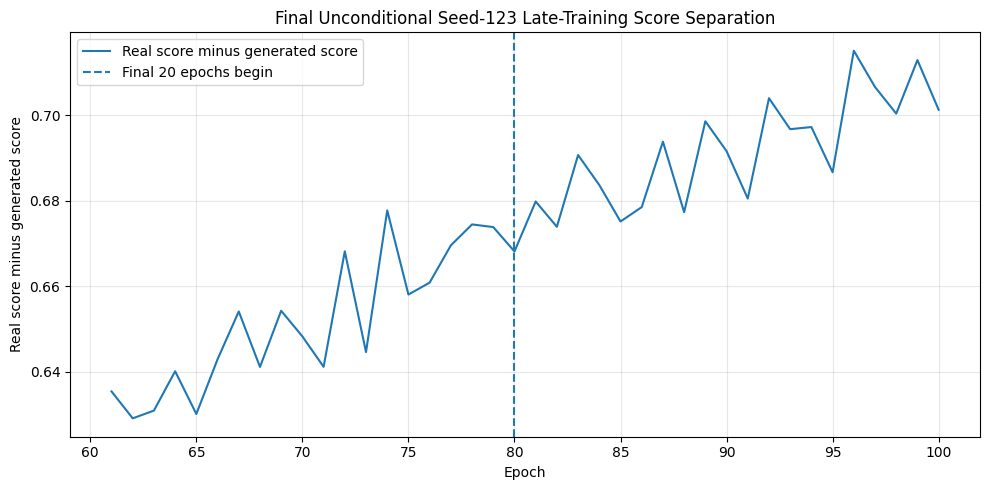

,Window,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean
0,Epochs 61–80,2.5832,0.0929,0.2495,0.0144,0.826,0.1738,0.6522,13.6519
1,Epochs 81–100,2.8504,0.0867,0.2221,0.0126,0.846,0.1538,0.6923,13.8453


Late score-separation change: 0.0401
Late-training summary saved: [local project directory]/histories/final_unconditional_seed123_late_training_summary.csv
Score-separation plot saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed123_late_score_separation.png
No checkpoint has been selected yet.
Protected test set remains unused.


In [66]:
required_seed123_late_training_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "pd",
    "np",
    "plt",
]

missing_seed123_late_training_objects = [
    name
    for name in required_seed123_late_training_objects
    if name not in globals()
]

assert not missing_seed123_late_training_objects, (
    "Incomplete seed-123 late-training setup:\n"
    + "\n".join(
        missing_seed123_late_training_objects
    )
)


seed123_history_df = (
    pd.read_csv(
        HISTORIES_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}"
            ".csv"
        )
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


required_seed123_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

missing_seed123_history_columns = [
    column
    for column in required_seed123_history_columns
    if column not in seed123_history_df.columns
]

assert not missing_seed123_history_columns, (
    "Seed-123 history is missing:\n"
    + "\n".join(
        missing_seed123_history_columns
    )
)

assert len(seed123_history_df) == 100

assert np.isfinite(
    seed123_history_df[
        required_seed123_history_columns
    ].to_numpy(dtype=np.float64)
).all()


seed123_history_df[
    "score_separation"
] = (
    seed123_history_df["real_score"]
    - seed123_history_df["fake_score"]
)


seed123_late_training_windows = [
    (
        "Epochs 61–80",
        61,
        80,
    ),
    (
        "Epochs 81–100",
        81,
        100,
    ),
]


seed123_late_training_rows = []


for window_label, start_epoch, end_epoch in (
    seed123_late_training_windows
):
    window_df = seed123_history_df.loc[
        seed123_history_df["epoch"].between(
            start_epoch,
            end_epoch,
        )
    ]

    assert len(window_df) == 20


    seed123_late_training_rows.append(
        {
            "Window": window_label,
            "Generator loss mean": (
                window_df[
                    "generator_loss"
                ].mean()
            ),
            "Generator loss SD": (
                window_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Discriminator loss mean": (
                window_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Discriminator loss SD": (
                window_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Real score mean": (
                window_df[
                    "real_score"
                ].mean()
            ),
            "Fake score mean": (
                window_df[
                    "fake_score"
                ].mean()
            ),
            "Score separation mean": (
                window_df[
                    "score_separation"
                ].mean()
            ),
            "Epoch time mean": (
                window_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


seed123_late_training_summary_df = (
    pd.DataFrame(
        seed123_late_training_rows
    )
)


FINAL_UNCONDITIONAL_SEED123_LATE_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed123_"
        "late_training_summary.csv"
    )
)

FINAL_UNCONDITIONAL_SEED123_SEPARATION_PLOT_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "late_score_separation.png"
    )
)


seed123_late_training_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_LATE_SUMMARY_PATH,
    index=False,
)


late_history_df = seed123_history_df.loc[
    seed123_history_df["epoch"] >= 61
]


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    late_history_df["epoch"],
    late_history_df["score_separation"],
    label=(
        "Real score minus generated score"
    ),
)

plt.axvline(
    80,
    linestyle="--",
    label="Final 20 epochs begin",
)

plt.xlabel("Epoch")
plt.ylabel("Real score minus generated score")

plt.title(
    "Final Unconditional Seed-123 "
    "Late-Training Score Separation"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FINAL_UNCONDITIONAL_SEED123_SEPARATION_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


display(
    seed123_late_training_summary_df.round(4)
)


seed123_separation_change = float(
    seed123_late_training_summary_df.loc[
        seed123_late_training_summary_df[
            "Window"
        ]
        == "Epochs 81–100",
        "Score separation mean",
    ].iloc[0]
    - seed123_late_training_summary_df.loc[
        seed123_late_training_summary_df[
            "Window"
        ]
        == "Epochs 61–80",
        "Score separation mean",
    ].iloc[0]
)


print(
    "Late score-separation change:",
    f"{seed123_separation_change:.4f}",
)

print(
    "Late-training summary saved:",
    FINAL_UNCONDITIONAL_SEED123_LATE_SUMMARY_PATH,
)

print(
    "Score-separation plot saved:",
    FINAL_UNCONDITIONAL_SEED123_SEPARATION_PLOT_PATH,
)

print(
    "No checkpoint has been selected yet."
)

print("Protected test set remains unused.")

#### Seed-123 Checkpoint Decision

The seed-123 milestone development FID results were:

| Epoch | Development FID |
|---:|---:|
| 50 | 40.3393 |
| 70 | 37.3253 |
| 90 | **35.8994** |
| 100 | 36.2180 |

Epoch `90` is selected.

It achieved the lowest milestone FID and remained within the strongest region of the fixed-seed progression. Epoch 100 produced broadly similar images, but its FID was `0.3186` points worse and it showed no clear visual improvement that would justify overriding the lower epoch-90 result.

The complete trajectory remained finite and smooth without abrupt collapse. Mean score separation increased from `0.6522` during epochs 61–80 to `0.6923` during epochs 81–100, indicating gradually stronger discriminator separation rather than a sudden instability.

Epochs 50 and 70 are rejected because their FID values were materially worse and their generated structures were generally less developed.

The selected seed-123 checkpoint is therefore epoch `90`.

In [68]:
required_seed123_selection_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_LATENT_DIM",
    "FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH",
    "FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_FID",
    "build_dcgan_generator",
    "make_augmented_discriminator_builder",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "WEIGHTS_DIR",
]

missing_seed123_selection_objects = [
    name
    for name in required_seed123_selection_objects
    if name not in globals()
]

assert not missing_seed123_selection_objects, (
    "Incomplete seed-123 checkpoint-selection setup:\n"
    + "\n".join(
        missing_seed123_selection_objects
    )
)


FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH = 90

FINAL_UNCONDITIONAL_SEED123_SELECTED_FID = float(
    FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_FID
)


assert (
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
    == FINAL_UNCONDITIONAL_SEED123_PROVISIONAL_EPOCH
)

assert np.isclose(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_FID,
    35.8994,
    atol=5e-5,
)


FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_MILESTONE_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        f"epoch{FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_MILESTONE_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        f"epoch{FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "generator.weights.h5"
    )
)

FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


for milestone_path in [
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_MILESTONE_PATH,
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_MILESTONE_PATH,
]:
    assert milestone_path.is_file(), (
        f"Missing selected milestone weights:\n"
        f"{milestone_path}"
    )


seed123_selected_discriminator_builder = (
    make_augmented_discriminator_builder(
        policy_name="flip_translation",
        augmentation_seed=123,
    )
)


final_unconditional_seed123_selected_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)

final_unconditional_seed123_selected_discriminator = (
    seed123_selected_discriminator_builder()
)


final_unconditional_seed123_selected_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_MILESTONE_PATH
)

final_unconditional_seed123_selected_discriminator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_MILESTONE_PATH
)


assert (
    final_unconditional_seed123_selected_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    final_unconditional_seed123_selected_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


final_unconditional_seed123_selected_generator.save_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)

final_unconditional_seed123_selected_discriminator.save_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
)


for selected_path in [
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH,
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH,
]:
    assert selected_path.is_file()
    assert selected_path.stat().st_size > 0


print(
    "Selected seed-123 checkpoint:",
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{FINAL_UNCONDITIONAL_SEED123_SELECTED_FID:.4f}",
)

print(
    "Selected generator saved:",
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator saved:",
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH,
)

print(
    "Reload verification has not yet been performed."
)

print("Protected test set remains unused.")

Selected seed-123 checkpoint: 90
Selected milestone FID: 35.8994
Selected generator saved: [local project directory]/weights/G09_final_unconditional_fliptranslation_seed123_generator.weights.h5
Selected discriminator saved: [local project directory]/weights/G09_final_unconditional_fliptranslation_seed123_discriminator.weights.h5
Reload verification has not yet been performed.
Protected test set remains unused.


In [69]:
required_seed123_reload_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_FID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_MILESTONE_PATH",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_MILESTONE_PATH",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH",
    "FINAL_UNCONDITIONAL_SEED123_LATENT_DIM",
    "build_dcgan_generator",
    "make_augmented_discriminator_builder",
    "make_stateless_noise",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "HISTORIES_DIR",
]

missing_seed123_reload_objects = [
    name
    for name in required_seed123_reload_objects
    if name not in globals()
]

assert not missing_seed123_reload_objects, (
    "Incomplete seed-123 reload-verification setup:\n"
    + "\n".join(
        missing_seed123_reload_objects
    )
)


seed123_reload_discriminator_builder = (
    make_augmented_discriminator_builder(
        policy_name="flip_translation",
        augmentation_seed=123,
    )
)


seed123_canonical_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)

seed123_canonical_discriminator = (
    seed123_reload_discriminator_builder()
)

seed123_canonical_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_MILESTONE_PATH
)

seed123_canonical_discriminator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_MILESTONE_PATH
)


seed123_reloaded_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)

seed123_reloaded_discriminator = (
    seed123_reload_discriminator_builder()
)

seed123_reloaded_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)

seed123_reloaded_discriminator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
)


assert seed123_canonical_generator.count_params() == (
    CURRENT_GENERATOR_PARAMETERS
)

assert seed123_reloaded_generator.count_params() == (
    CURRENT_GENERATOR_PARAMETERS
)

assert seed123_canonical_discriminator.count_params() == (
    CURRENT_DISCRIMINATOR_PARAMETERS
)

assert seed123_reloaded_discriminator.count_params() == (
    CURRENT_DISCRIMINATOR_PARAMETERS
)


seed123_generator_weight_difference = max(
    (
        float(
            np.max(
                np.abs(
                    canonical_weight
                    - reloaded_weight
                )
            )
        )
        for canonical_weight, reloaded_weight in zip(
            seed123_canonical_generator.get_weights(),
            seed123_reloaded_generator.get_weights(),
        )
    ),
    default=0.0,
)

seed123_discriminator_weight_difference = max(
    (
        float(
            np.max(
                np.abs(
                    canonical_weight
                    - reloaded_weight
                )
            )
        )
        for canonical_weight, reloaded_weight in zip(
            seed123_canonical_discriminator.get_weights(),
            seed123_reloaded_discriminator.get_weights(),
        )
    ),
    default=0.0,
)


seed123_reload_noise = make_stateless_noise(
    sample_count=16,
    latent_dim=(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    ),
    seed=9123,
)


seed123_canonical_images = (
    seed123_canonical_generator(
        seed123_reload_noise,
        training=False,
    )
)

seed123_reloaded_images = (
    seed123_reloaded_generator(
        seed123_reload_noise,
        training=False,
    )
)


seed123_generator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            seed123_canonical_images
            - seed123_reloaded_images
        )
    ).numpy()
)


seed123_canonical_scores = (
    seed123_canonical_discriminator(
        seed123_canonical_images,
        training=False,
    )
)

seed123_reloaded_scores = (
    seed123_reloaded_discriminator(
        seed123_canonical_images,
        training=False,
    )
)


seed123_discriminator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            seed123_canonical_scores
            - seed123_reloaded_scores
        )
    ).numpy()
)


assert seed123_canonical_images.shape == (
    16,
    32,
    32,
    3,
)

assert seed123_reloaded_images.shape == (
    16,
    32,
    32,
    3,
)

assert seed123_canonical_scores.shape == (
    16,
    1,
)

assert np.isfinite(
    seed123_canonical_images.numpy()
).all()

assert np.isfinite(
    seed123_reloaded_images.numpy()
).all()

assert float(
    tf.reduce_min(
        seed123_reloaded_images
    ).numpy()
) >= -1.0001

assert float(
    tf.reduce_max(
        seed123_reloaded_images
    ).numpy()
) <= 1.0001


assert seed123_generator_weight_difference < 1e-7
assert seed123_discriminator_weight_difference < 1e-7

assert seed123_generator_output_difference < 1e-5
assert seed123_discriminator_output_difference < 1e-5


FINAL_UNCONDITIONAL_SEED123_RELOAD_VERIFIED = True


final_unconditional_seed123_checkpoint_decision_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED123_RUN_ID
                ),
                "Training seed": 123,
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
                ),
                "Selected milestone FID": (
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_FID
                ),
                "Generator path": str(
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
                ),
                "Discriminator path": str(
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
                ),
                "Reload verified": (
                    FINAL_UNCONDITIONAL_SEED123_RELOAD_VERIFIED
                ),
                "Decision": (
                    "Epoch 90 selected because it had "
                    "the lowest milestone FID, remained "
                    "visually valid and had no stability "
                    "veto. Epoch 100 showed no clear "
                    "qualitative advantage."
                ),
            }
        ]
    )
)


FINAL_UNCONDITIONAL_SEED123_CHECKPOINT_DECISION_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed123_"
        "checkpoint_decision.csv"
    )
)

final_unconditional_seed123_checkpoint_decision_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_CHECKPOINT_DECISION_PATH,
    index=False,
)


display(
    final_unconditional_seed123_checkpoint_decision_df
)


print(
    "Seed-123 selected-weight reload "
    "verification passed."
)

print(
    "Maximum generator weight difference:",
    f"{seed123_generator_weight_difference:.10f}",
)

print(
    "Maximum discriminator weight difference:",
    f"{seed123_discriminator_weight_difference:.10f}",
)

print(
    "Maximum generator output difference:",
    f"{seed123_generator_output_difference:.10f}",
)

print(
    "Maximum discriminator output difference:",
    f"{seed123_discriminator_output_difference:.10f}",
)

print(
    "Checkpoint decision saved:",
    FINAL_UNCONDITIONAL_SEED123_CHECKPOINT_DECISION_PATH,
)

print(
    "No cross-seed final-unconditional "
    "decision has been made."
)

print("Protected test set remains unused.")


final_unconditional_seed123_selected_generator = (
    seed123_reloaded_generator
)

final_unconditional_seed123_selected_discriminator = (
    seed123_reloaded_discriminator
)


del seed123_canonical_generator
del seed123_canonical_discriminator

gc.collect()

,Run ID,Training seed,Selected epoch,Selected milestone FID,Generator path,Discriminator path,Reload verified,Decision
0,G09_final_unconditional_fliptranslation_seed123,123,90,35.899368,[local project directory]/weights...,[local project directory]/weights...,True,Epoch 90 selected because it had the lowest mi...


Seed-123 selected-weight reload verification passed.
Maximum generator weight difference: 0.0000000000
Maximum discriminator weight difference: 0.0000000000
Maximum generator output difference: 0.0000001788
Maximum discriminator output difference: 0.0000000000
Checkpoint decision saved: [local project directory]/histories/final_unconditional_seed123_checkpoint_decision.csv
No cross-seed final-unconditional decision has been made.
Protected test set remains unused.


20515

#### Seed-123 Selected-Checkpoint Repeated FID

The selected epoch-90 generator is evaluated using three independent generated samples.

Each repeat uses:

- 5,000 generated images;
- seeds `1002`, `1003` and `1004`;
- the same frozen InceptionV3 feature extractor;
- the same 50,000-image CIFAR-10 training reference;
- ordinary unaugmented generator outputs.

The individual FID values, mean and sample standard deviation are reported. This measures generated-sample variation for the selected checkpoint. It does not measure variation across independently trained GANs.

In [71]:
required_seed123_repeated_fid_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH",
    "FINAL_UNCONDITIONAL_SEED123_LATENT_DIM",
    "FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH",
    "FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT",
    "FINAL_UNCONDITIONAL_FID_BATCH_SIZE",
    "FINAL_UNCONDITIONAL_FID_FEATURE_DIM",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "HISTORIES_DIR",
]

missing_seed123_repeated_fid_objects = [
    name
    for name in required_seed123_repeated_fid_objects
    if name not in globals()
]

assert not missing_seed123_repeated_fid_objects, (
    "Incomplete seed-123 repeated-FID setup:\n"
    + "\n".join(
        missing_seed123_repeated_fid_objects
    )
)


FINAL_UNCONDITIONAL_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)


FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


assert FINAL_UNCONDITIONAL_REPEATED_FID_SEEDS == (
    1002,
    1003,
    1004,
)

assert FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_FID_FEATURE_DIM == 2_048

assert (
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
    == 90
)

assert (
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
    .is_file()
)


seed123_repeated_fid_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)

seed123_repeated_fid_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)


print(
    "Seed-123 selected generator loaded."
)

print(
    "Selected epoch:",
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH,
)

print(
    "Repeated FID seeds:",
    FINAL_UNCONDITIONAL_REPEATED_FID_SEEDS,
)

print(
    "Generated images per repeat:",
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
)

print("Protected test set remains unused.")

Seed-123 selected generator loaded.
Selected epoch: 90
Repeated FID seeds: (1002, 1003, 1004)
Generated images per repeat: 5000
Protected test set remains unused.


In [72]:
seed123_repeated_fid_rows = []


for repeat_seed in (
    FINAL_UNCONDITIONAL_REPEATED_FID_SEEDS
):
    generated_images = generate_images_uint8(
        generator=seed123_repeated_fid_generator,
        sample_count=(
            FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
        ),
        seed=repeat_seed,
    )


    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=(
            FINAL_UNCONDITIONAL_FID_BATCH_SIZE
        ),
    )


    assert generated_images.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8

    assert generated_features.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    repeat_fid = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )


    assert np.isfinite(repeat_fid)


    seed123_repeated_fid_rows.append(
        {
            "evaluation": (
                "selected_checkpoint_repeat"
            ),
            "epoch": (
                FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "seed": int(repeat_seed),
            "sample_count": (
                FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
            ),
            "fid": float(repeat_fid),
        }
    )


    print(
        f"Seed {repeat_seed} FID: "
        f"{repeat_fid:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


final_unconditional_seed123_repeated_fid_df = (
    pd.DataFrame(
        seed123_repeated_fid_rows
    )
)


assert len(
    final_unconditional_seed123_repeated_fid_df
) == 3

assert tuple(
    final_unconditional_seed123_repeated_fid_df[
        "seed"
    ].astype(int)
) == FINAL_UNCONDITIONAL_REPEATED_FID_SEEDS

assert set(
    final_unconditional_seed123_repeated_fid_df[
        "epoch"
    ].astype(int)
) == {
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
}

assert set(
    final_unconditional_seed123_repeated_fid_df[
        "sample_count"
    ].astype(int)
) == {
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
}


FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_MEAN = float(
    final_unconditional_seed123_repeated_fid_df[
        "fid"
    ].mean()
)

FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SD = float(
    final_unconditional_seed123_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)


final_unconditional_seed123_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED123_RUN_ID
                ),
                "Training seed": 123,
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
                ),
                "Repeat count": 3,
                "Repeated FID mean": (
                    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SD
                ),
                "Repeated FID minimum": float(
                    final_unconditional_seed123_repeated_fid_df[
                        "fid"
                    ].min()
                ),
                "Repeated FID maximum": float(
                    final_unconditional_seed123_repeated_fid_df[
                        "fid"
                    ].max()
                ),
            }
        ]
    )
)


final_unconditional_seed123_repeated_fid_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_PATH,
    index=False,
)

final_unconditional_seed123_repeated_fid_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


existing_seed123_fid_results_df = pd.read_csv(
    FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH
)

seed123_milestone_only_df = (
    existing_seed123_fid_results_df.loc[
        existing_seed123_fid_results_df[
            "evaluation"
        ].astype(str)
        == "milestone"
    ]
    .copy()
)


final_unconditional_seed123_all_fid_df = (
    pd.concat(
        [
            seed123_milestone_only_df,
            final_unconditional_seed123_repeated_fid_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "evaluation",
            "epoch",
            "seed",
        ]
    )
    .reset_index(drop=True)
)


final_unconditional_seed123_all_fid_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH,
    index=False,
)


display(
    final_unconditional_seed123_repeated_fid_df.round(4)
)

display(
    final_unconditional_seed123_repeated_fid_summary_df.round(4)
)


print(
    "Seed-123 repeated FID:",
    (
        f"{FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID results saved:",
    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_PATH,
)

print(
    "Repeated-FID summary saved:",
    FINAL_UNCONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH,
)

print(
    "Combined milestone and repeated FID saved:",
    FINAL_UNCONDITIONAL_SEED123_FID_RESULTS_PATH,
)

print(
    "No cross-training-seed decision "
    "has been made."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 36.0319


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 35.3366


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1004 FID: 35.6678


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,90,1002,5000,36.0319
1,selected_checkpoint_repeat,90,1003,5000,35.3366
2,selected_checkpoint_repeat,90,1004,5000,35.6678


,Run ID,Training seed,Selected epoch,Repeat count,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum
0,G09_final_unconditional_fliptranslation_seed123,123,90,3,35.6788,0.3478,35.3366,36.0319


Seed-123 repeated FID: 35.6788 ± 0.3478
Repeated-FID results saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed123_selected_repeated_fid.csv
Repeated-FID summary saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed123_selected_repeated_fid_summary.csv
Combined milestone and repeated FID saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed123_fid_results.csv
No cross-training-seed decision has been made.
Protected test set remains unused.


#### Seed-123 Manual Quality Evaluation

The selected epoch-90 generator produces 100 uncurated images using fixed manual-scoring seed `1201`.

Each image will be classified as:

- **Clear:** immediately recognisable object-like structure with reasonably coherent overall organisation;
- **Marginal:** meaningful category or object cues are present, but substantial blur, deformation, weak boundaries or ambiguity remains;
- **Nonsense:** no stable object interpretation or meaningful class-related structure is defensible.

The same strict scoring standard and fixed latent seed used for the earlier formal manual evaluations are retained. The counts must sum to 100.

The grid is generated and saved before any scores are entered.

In [73]:
required_seed123_manual_grid_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SEED123_LATENT_DIM",
    "final_unconditional_seed123_selected_generator",
    "generate_images_uint8",
    "GRIDS_DIR",
]

missing_seed123_manual_grid_objects = [
    name
    for name in required_seed123_manual_grid_objects
    if name not in globals()
]

assert not missing_seed123_manual_grid_objects, (
    "Incomplete seed-123 manual-grid setup:\n"
    + "\n".join(
        missing_seed123_manual_grid_objects
    )
)


FINAL_UNCONDITIONAL_MANUAL_SAMPLE_COUNT = 100
FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED = 1201


FINAL_UNCONDITIONAL_SEED123_MANUAL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "manual_100.png"
    )
)


final_unconditional_seed123_manual_images = (
    generate_images_uint8(
        generator=(
            final_unconditional_seed123_selected_generator
        ),
        sample_count=(
            FINAL_UNCONDITIONAL_MANUAL_SAMPLE_COUNT
        ),
        latent_dim=(
            FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
        ),
        seed=(
            FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED
        ),
    )
)


assert final_unconditional_seed123_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert (
    final_unconditional_seed123_manual_images.dtype
    == np.uint8
)

assert np.isfinite(
    final_unconditional_seed123_manual_images
).all()


figure, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15),
)


for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        final_unconditional_seed123_manual_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=7,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Final Unconditional Seed-123 "
        "Manual Evaluation\n"
        f"Selected Epoch "
        f"{FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH}"
    ),
    fontsize=15,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.97)
)

figure.savefig(
    FINAL_UNCONDITIONAL_SEED123_MANUAL_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Seed-123 numbered manual grid saved:",
    FINAL_UNCONDITIONAL_SEED123_MANUAL_GRID_PATH,
)

print(
    "Manual-scoring seed:",
    FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED,
)

print(
    "Manual counts have not been entered."
)

print(
    "No cross-training-seed decision "
    "has been made."
)

print("Protected test set remains unused.")

Seed-123 numbered manual grid saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed123_manual_100.png
Manual-scoring seed: 1201
Manual counts have not been entered.
No cross-training-seed decision has been made.
Protected test set remains unused.


#### Seed-123 Manual Quality Result

Using fixed manual-scoring seed `1201` and the same strict definitions used for the seed-42 final-unconditional candidate, the selected seed-123 checkpoint was scored as:

**24 Clear / 68 Marginal / 8 Nonsense**

A strict Clear threshold was retained. Images were classified as Clear only when the generated object was immediately recognisable and retained reasonably coherent overall structure. Images with identifiable category cues but substantial deformation, malformed anatomy, weak boundaries or ambiguous composition remained Marginal.

The reused seed-42 final-unconditional run was previously scored as:

**22 Clear / 70 Marginal / 8 Nonsense**

Seed 123 therefore produced:

- `2` more Clear images;
- `2` fewer Marginal images;
- the same number of Nonsense images.

The two-image Clear difference is well below the approximate 13-image manual-resolution threshold. Manual evidence therefore treats the seed-42 and seed-123 checkpoints as practically similar rather than establishing a meaningful seed-123 advantage.

No cross-training-seed final-unconditional decision has been made.

In [77]:
required_seed123_manual_result_objects = [
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED",
    "FINAL_UNCONDITIONAL_SEED123_MANUAL_GRID_PATH",
    "HISTORIES_DIR",
]

missing_seed123_manual_result_objects = [
    name
    for name in required_seed123_manual_result_objects
    if name not in globals()
]

assert not missing_seed123_manual_result_objects, (
    "Incomplete seed-123 manual-result setup:\n"
    + "\n".join(
        missing_seed123_manual_result_objects
    )
)


FINAL_UNCONDITIONAL_SEED42_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS = {
    "Clear": 22,
    "Marginal": 70,
    "Nonsense": 8,
}

FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS = {
    "Clear": 24,
    "Marginal": 68,
    "Nonsense": 8,
}

FINAL_UNCONDITIONAL_MANUAL_RESOLUTION = 13


assert FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED == 1201

assert (
    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
    == 90
)

assert (
    FINAL_UNCONDITIONAL_SEED123_MANUAL_GRID_PATH
    .is_file()
)

assert sum(
    FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS.values()
) == 100

assert sum(
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS.values()
) == 100


seed123_clear_difference = (
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS[
        "Clear"
    ]
    - FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS[
        "Clear"
    ]
)

seed123_marginal_difference = (
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS[
        "Marginal"
    ]
    - FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS[
        "Marginal"
    ]
)

seed123_nonsense_difference = (
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS[
        "Nonsense"
    ]
    - FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS[
        "Nonsense"
    ]
)


final_unconditional_seed123_manual_result_df = (
    pd.DataFrame(
        [
            {
                "Configuration": (
                    "Final unconditional, seed 42"
                ),
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED42_RUN_ID
                ),
                "Training seed": 42,
                "Selected epoch": 100,
                "Manual seed": (
                    FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED
                ),
                **FINAL_UNCONDITIONAL_SEED42_MANUAL_COUNTS,
            },
            {
                "Configuration": (
                    "Final unconditional, seed 123"
                ),
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED123_RUN_ID
                ),
                "Training seed": 123,
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
                ),
                "Manual seed": (
                    FINAL_UNCONDITIONAL_MANUAL_SCORING_SEED
                ),
                **FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS,
            },
        ]
    )
)


final_unconditional_seed123_manual_comparison_df = (
    pd.DataFrame(
        [
            {
                "Comparison": (
                    "Seed 123 minus seed 42"
                ),
                "Clear difference": (
                    seed123_clear_difference
                ),
                "Marginal difference": (
                    seed123_marginal_difference
                ),
                "Nonsense difference": (
                    seed123_nonsense_difference
                ),
                "Manual resolution": (
                    FINAL_UNCONDITIONAL_MANUAL_RESOLUTION
                ),
                "Absolute Clear difference meets resolution": (
                    abs(seed123_clear_difference)
                    >= FINAL_UNCONDITIONAL_MANUAL_RESOLUTION
                ),
                "Manual interpretation": (
                    "Practically similar"
                ),
            }
        ]
    )
)


FINAL_UNCONDITIONAL_SEED123_MANUAL_RESULT_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed123_manual_quality.csv"
)

FINAL_UNCONDITIONAL_SEED123_MANUAL_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "manual_comparison.csv"
    )
)


final_unconditional_seed123_manual_result_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_MANUAL_RESULT_PATH,
    index=False,
)

final_unconditional_seed123_manual_comparison_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COMPARISON_PATH,
    index=False,
)


display(
    final_unconditional_seed123_manual_result_df
)

display(
    final_unconditional_seed123_manual_comparison_df
)


print(
    "Seed-123 manual result:",
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COUNTS,
)

print(
    "Clear-image difference from seed 42:",
    seed123_clear_difference,
)

print(
    "Manual difference meets resolution:",
    abs(seed123_clear_difference)
    >= FINAL_UNCONDITIONAL_MANUAL_RESOLUTION,
)

print(
    "Manual results saved:",
    FINAL_UNCONDITIONAL_SEED123_MANUAL_RESULT_PATH,
)

print(
    "Manual comparison saved:",
    FINAL_UNCONDITIONAL_SEED123_MANUAL_COMPARISON_PATH,
)

print(
    "No cross-training-seed final-unconditional "
    "decision has been made."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Training seed,Selected epoch,Manual seed,Clear,Marginal,Nonsense
0,"Final unconditional, seed 42",G08_augmentation_fliptranslation_seed42,42,100,1201,22,70,8
1,"Final unconditional, seed 123",G09_final_unconditional_fliptranslation_seed123,123,90,1201,24,68,8


,Comparison,Clear difference,Marginal difference,Nonsense difference,Manual resolution,Absolute Clear difference meets resolution,Manual interpretation
0,Seed 123 minus seed 42,2,-2,0,13,False,Practically similar


Seed-123 manual result: {'Clear': 24, 'Marginal': 68, 'Nonsense': 8}
Clear-image difference from seed 42: 2
Manual difference meets resolution: False
Manual results saved: [local project directory]/histories/final_unconditional_seed123_manual_quality.csv
Manual comparison saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_manual_comparison.csv
No cross-training-seed final-unconditional decision has been made.
Protected test set remains unused.


In [78]:
required_final_unconditional_coverage_pool_objects = [
    "WEIGHTS_DIR",
    "build_dcgan_generator",
    "generate_images_uint8",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH",
    "FINAL_UNCONDITIONAL_SEED123_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
]

missing_final_unconditional_coverage_pool_objects = [
    name
    for name in required_final_unconditional_coverage_pool_objects
    if name not in globals()
]

assert not missing_final_unconditional_coverage_pool_objects, (
    "Incomplete final-unconditional coverage-pool setup:\n"
    + "\n".join(
        missing_final_unconditional_coverage_pool_objects
    )
)


FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT = 5_000
FINAL_UNCONDITIONAL_EVALUATION_SEED = 1302
FINAL_UNCONDITIONAL_EVALUATION_BATCH_SIZE = 256

FINAL_UNCONDITIONAL_SEED42_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

FINAL_UNCONDITIONAL_SEED42_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED42_RUN_ID}_"
        "generator.weights.h5"
    )
)


assert FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_EVALUATION_SEED == 1302

assert (
    FINAL_UNCONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
    .is_file()
)

assert (
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
    .is_file()
)


final_unconditional_seed42_evaluation_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)

final_unconditional_seed123_evaluation_generator = (
    build_dcgan_generator(
        FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
    )
)


final_unconditional_seed42_evaluation_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
)

final_unconditional_seed123_evaluation_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)


assert (
    final_unconditional_seed42_evaluation_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    final_unconditional_seed123_evaluation_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)


final_unconditional_seed42_evaluation_images = (
    generate_images_uint8(
        generator=(
            final_unconditional_seed42_evaluation_generator
        ),
        sample_count=(
            FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
        ),
        latent_dim=(
            FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
        ),
        seed=FINAL_UNCONDITIONAL_EVALUATION_SEED,
        batch_size=(
            FINAL_UNCONDITIONAL_EVALUATION_BATCH_SIZE
        ),
    )
)

final_unconditional_seed123_evaluation_images = (
    generate_images_uint8(
        generator=(
            final_unconditional_seed123_evaluation_generator
        ),
        sample_count=(
            FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
        ),
        latent_dim=(
            FINAL_UNCONDITIONAL_SEED123_LATENT_DIM
        ),
        seed=FINAL_UNCONDITIONAL_EVALUATION_SEED,
        batch_size=(
            FINAL_UNCONDITIONAL_EVALUATION_BATCH_SIZE
        ),
    )
)


for image_pool in [
    final_unconditional_seed42_evaluation_images,
    final_unconditional_seed123_evaluation_images,
]:
    assert image_pool.shape == (
        5_000,
        32,
        32,
        3,
    )

    assert image_pool.dtype == np.uint8
    assert np.isfinite(image_pool).all()


print(
    "Matched final-unconditional evaluation pools created."
)

print(
    "Seed-42 pool:",
    final_unconditional_seed42_evaluation_images.shape,
)

print(
    "Seed-123 pool:",
    final_unconditional_seed123_evaluation_images.shape,
)

print(
    "Evaluation seed:",
    FINAL_UNCONDITIONAL_EVALUATION_SEED,
)

print(
    "Pools remain in memory for coverage, "
    "descriptors and diversity."
)

print("Protected test set remains unused.")


del final_unconditional_seed42_evaluation_generator
del final_unconditional_seed123_evaluation_generator

gc.collect()

Matched final-unconditional evaluation pools created.
Seed-42 pool: (5000, 32, 32, 3)
Seed-123 pool: (5000, 32, 32, 3)
Evaluation seed: 1302
Pools remain in memory for coverage, descriptors and diversity.
Protected test set remains unused.


3025

In [79]:
required_final_unconditional_coverage_objects = [
    "final_unconditional_seed42_evaluation_images",
    "final_unconditional_seed123_evaluation_images",
    "summarise_classifier_coverage",
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
    "REAL_CLASSIFIER_PREDICTED_PROPORTIONS",
    "CLASS_NAMES",
    "HISTORIES_DIR",
]

missing_final_unconditional_coverage_objects = [
    name
    for name in required_final_unconditional_coverage_objects
    if name not in globals()
]

assert not missing_final_unconditional_coverage_objects, (
    "Incomplete final-unconditional coverage setup:\n"
    + "\n".join(
        missing_final_unconditional_coverage_objects
    )
)


assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False


(
    final_unconditional_seed42_distribution_df,
    final_unconditional_seed42_coverage_df,
    final_unconditional_seed42_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        final_unconditional_seed42_evaluation_images
    ),
    model_label="Final unconditional, seed 42",
    batch_size=(
        FINAL_UNCONDITIONAL_EVALUATION_BATCH_SIZE
    ),
)

(
    final_unconditional_seed123_distribution_df,
    final_unconditional_seed123_coverage_df,
    final_unconditional_seed123_predictions,
) = summarise_classifier_coverage(
    images_uint8=(
        final_unconditional_seed123_evaluation_images
    ),
    model_label="Final unconditional, seed 123",
    batch_size=(
        FINAL_UNCONDITIONAL_EVALUATION_BATCH_SIZE
    ),
)


final_unconditional_seed123_coverage_summary_df = (
    pd.concat(
        [
            final_unconditional_seed42_coverage_df,
            final_unconditional_seed123_coverage_df,
        ],
        ignore_index=True,
    )
)


final_unconditional_seed42_distribution_df.insert(
    0,
    "Configuration",
    "Final unconditional, seed 42",
)

final_unconditional_seed123_distribution_df.insert(
    0,
    "Configuration",
    "Final unconditional, seed 123",
)


final_unconditional_seed123_class_distribution_df = (
    pd.concat(
        [
            final_unconditional_seed42_distribution_df,
            final_unconditional_seed123_distribution_df,
        ],
        ignore_index=True,
    )
)


FINAL_UNCONDITIONAL_SEED123_COVERAGE_SUMMARY_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed42_vs_seed123_coverage.csv"
)

FINAL_UNCONDITIONAL_SEED123_CLASS_DISTRIBUTION_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "class_distribution.csv"
    )
)


final_unconditional_seed123_coverage_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_COVERAGE_SUMMARY_PATH,
    index=False,
)

final_unconditional_seed123_class_distribution_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_CLASS_DISTRIBUTION_PATH,
    index=False,
)


coverage_display_columns = [
    "Model",
    "Sample count",
    "Represented classes",
    "Dominant-class share",
    "Normalised class entropy",
    "JS divergence from real predictions",
]


display(
    final_unconditional_seed123_coverage_summary_df[
        coverage_display_columns
    ].round(4)
)


final_unconditional_seed123_class_proportion_table = (
    final_unconditional_seed123_class_distribution_df
    .pivot(
        index="Class",
        columns="Configuration",
        values="Predicted proportion",
    )
    .reindex(CLASS_NAMES)
)

final_unconditional_seed123_class_proportion_table.insert(
    0,
    "Real validation reference",
    REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
)


display(
    final_unconditional_seed123_class_proportion_table.round(4)
)


FINAL_UNCONDITIONAL_SEED42_COVERAGE_JS = float(
    final_unconditional_seed42_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

FINAL_UNCONDITIONAL_SEED123_COVERAGE_JS = float(
    final_unconditional_seed123_coverage_df[
        "JS divergence from real predictions"
    ].iloc[0]
)

final_unconditional_seed123_js_difference = float(
    FINAL_UNCONDITIONAL_SEED123_COVERAGE_JS
    - FINAL_UNCONDITIONAL_SEED42_COVERAGE_JS
)


print(
    "Seed 123 minus seed 42 JS divergence:",
    f"{final_unconditional_seed123_js_difference:.4f}",
)

print(
    "Coverage summary saved:",
    FINAL_UNCONDITIONAL_SEED123_COVERAGE_SUMMARY_PATH,
)

print(
    "Class distribution saved:",
    FINAL_UNCONDITIONAL_SEED123_CLASS_DISTRIBUTION_PATH,
)

print(
    "The matched 5,000-image pools remain "
    "in memory for later safeguards."
)

print(
    "Coverage evidence is supporting evidence, "
    "not generated-image ground truth."
)

print("Protected test set remains unused.")

,Model,Sample count,Represented classes,Dominant-class share,Normalised class entropy,JS divergence from real predictions
0,"Final unconditional, seed 42",5000,10,0.1800,0.9713,0.0172
1,"Final unconditional, seed 123",5000,10,0.1608,0.9822,0.0094


Configuration,Real validation reference,"Final unconditional, seed 123","Final unconditional, seed 42"
Class,,,
airplane,0.1004,0.1168,0.0974
automobile,0.1008,0.0774,0.0634
bird,0.0908,0.0724,0.0832
cat,0.1010,0.1018,0.0880
deer,0.1068,0.1246,0.1500
dog,0.0894,0.0518,0.0470
frog,0.1140,0.1608,0.1800
horse,0.0992,0.0942,0.0818
ship,0.0986,0.1016,0.1066


Seed 123 minus seed 42 JS divergence: -0.0077
Coverage summary saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_coverage.csv
Class distribution saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_class_distribution.csv
The matched 5,000-image pools remain in memory for later safeguards.
Coverage evidence is supporting evidence, not generated-image ground truth.
Protected test set remains unused.


In [80]:
required_final_unconditional_grouped_grid_objects = [
    "final_unconditional_seed42_evaluation_images",
    "final_unconditional_seed123_evaluation_images",
    "final_unconditional_seed42_predictions",
    "final_unconditional_seed123_predictions",
    "save_classifier_grouped_comparison",
    "GRIDS_DIR",
    "HISTORIES_DIR",
]

missing_final_unconditional_grouped_grid_objects = [
    name
    for name in required_final_unconditional_grouped_grid_objects
    if name not in globals()
]

assert not missing_final_unconditional_grouped_grid_objects, (
    "Incomplete final-unconditional grouped-grid setup:\n"
    + "\n".join(
        missing_final_unconditional_grouped_grid_objects
    )
)


FINAL_UNCONDITIONAL_COVERAGE_GRID_SEED = 1401

FINAL_UNCONDITIONAL_SEED123_GROUPED_GRID_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "class_grouped_comparison.png"
    )
)

FINAL_UNCONDITIONAL_SEED123_GROUPED_COUNTS_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "class_grouped_counts.csv"
    )
)


final_unconditional_seed123_grouped_counts_df = (
    save_classifier_grouped_comparison(
        reference_images=(
            final_unconditional_seed42_evaluation_images
        ),
        reference_predictions=(
            final_unconditional_seed42_predictions
        ),
        candidate_images=(
            final_unconditional_seed123_evaluation_images
        ),
        candidate_predictions=(
            final_unconditional_seed123_predictions
        ),
        reference_label="Seed 42",
        candidate_label="Seed 123",
        output_path=(
            FINAL_UNCONDITIONAL_SEED123_GROUPED_GRID_PATH
        ),
        seed=FINAL_UNCONDITIONAL_COVERAGE_GRID_SEED,
        title=(
            "Final Unconditional Seed-42 "
            "and Seed-123 Class-Coverage Comparison"
        ),
        images_per_class=5,
    )
)


final_unconditional_seed123_grouped_counts_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_GROUPED_COUNTS_PATH,
    index=False,
)


display(
    final_unconditional_seed123_grouped_counts_df
)


print(
    "Coverage-grid sampling seed:",
    FINAL_UNCONDITIONAL_COVERAGE_GRID_SEED,
)

print(
    "Classifier-grouped comparison saved:",
    FINAL_UNCONDITIONAL_SEED123_GROUPED_GRID_PATH,
)

print(
    "Grouped counts saved:",
    FINAL_UNCONDITIONAL_SEED123_GROUPED_COUNTS_PATH,
)

print(
    "The existing matched 5,000-image pools were reused."
)

print(
    "Rows use frozen-classifier predictions, "
    "not generated-image ground truth."
)

print("Protected test set remains unused.")

,Class,Seed 42 predicted count,Seed 123 predicted count
0,airplane,487,584
1,automobile,317,387
2,bird,416,362
3,cat,440,509
4,deer,750,623
5,dog,235,259
6,frog,900,804
7,horse,409,471
8,ship,533,508
9,truck,513,493


Coverage-grid sampling seed: 1401
Classifier-grouped comparison saved: [local project directory]/grids/final_unconditional_seed42_vs_seed123_class_grouped_comparison.png
Grouped counts saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_class_grouped_counts.csv
The existing matched 5,000-image pools were reused.
Rows use frozen-classifier predictions, not generated-image ground truth.
Protected test set remains unused.


#### Seed-123 Coverage Interpretation

Both final-unconditional training seeds produced samples assigned to all ten CIFAR-10 classes by the frozen coverage classifier.

Seed `123` showed stronger distributional coverage than seed `42`:

- dominant-class share decreased from `0.1800` to `0.1608`;
- normalised class entropy increased from `0.9713` to `0.9822`;
- Jensen-Shannon divergence from the held-out real prediction distribution decreased from `0.0172` to `0.0094`.

The reduction of `0.0077` in Jensen-Shannon divergence indicates that the seed-123 predicted-class distribution is more closely aligned with the real validation prediction distribution.

The classifier-grouped grid also contains plausible examples across every predicted class for both seeds. Seed `123` appears less concentrated in frog and deer predictions, although some class imbalance remains.

Coverage therefore provides supporting evidence in favour of seed `123`. This does not establish ground-truth class correctness because the row assignments are frozen-classifier predictions rather than verified labels.

No cross-training-seed final-unconditional decision has been made.

#### Seed-42 and Seed-123 Descriptor Comparison

The same matched 5,000-image pools are compared against the protected CIFAR-10 training descriptor reference.

Seven low-level image properties are evaluated:

- brightness;
- contrast;
- mean red;
- mean green;
- mean blue;
- saturation;
- edge strength.

For each training seed, the analysis compares both the descriptor mean and descriptor standard deviation against the real training distribution.

These descriptors measure low-level colour, intensity and edge alignment. They do not directly measure object recognisability or semantic correctness.

In [81]:
required_final_unconditional_descriptor_objects = [
    "final_unconditional_seed42_evaluation_images",
    "final_unconditional_seed123_evaluation_images",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "real_descriptor_df",
    "DESCRIPTOR_COLUMNS",
    "HISTORIES_DIR",
]

missing_final_unconditional_descriptor_objects = [
    name
    for name in required_final_unconditional_descriptor_objects
    if name not in globals()
]

assert not missing_final_unconditional_descriptor_objects, (
    "Incomplete final-unconditional descriptor setup:\n"
    + "\n".join(
        missing_final_unconditional_descriptor_objects
    )
)


for image_pool in [
    final_unconditional_seed42_evaluation_images,
    final_unconditional_seed123_evaluation_images,
]:
    assert image_pool.shape == (
        FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert image_pool.dtype == np.uint8


final_unconditional_seed42_descriptors = (
    calculate_image_descriptors(
        final_unconditional_seed42_evaluation_images
    )
)

final_unconditional_seed123_descriptors = (
    calculate_image_descriptors(
        final_unconditional_seed123_evaluation_images
    )
)


for descriptor_df in [
    final_unconditional_seed42_descriptors,
    final_unconditional_seed123_descriptors,
]:
    assert len(descriptor_df) == 5_000

    assert list(
        descriptor_df.columns
    ) == DESCRIPTOR_COLUMNS

    assert np.isfinite(
        descriptor_df.to_numpy()
    ).all()


final_unconditional_seed42_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptor_df,
        final_unconditional_seed42_descriptors,
    )
)

final_unconditional_seed123_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptor_df,
        final_unconditional_seed123_descriptors,
    )
)


final_unconditional_seed42_descriptor_comparison_df = (
    final_unconditional_seed42_descriptor_comparison_df
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)

final_unconditional_seed123_descriptor_comparison_df = (
    final_unconditional_seed123_descriptor_comparison_df
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)


FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_"
        "descriptor_comparison.csv"
    )
)

FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed123_"
        "descriptor_comparison.csv"
    )
)


final_unconditional_seed42_descriptor_comparison_df.to_csv(
    FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)

final_unconditional_seed123_descriptor_comparison_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)


print("Final unconditional seed-42 descriptor comparison")

display(
    final_unconditional_seed42_descriptor_comparison_df.round(4)
)


print("Final unconditional seed-123 descriptor comparison")

display(
    final_unconditional_seed123_descriptor_comparison_df.round(4)
)


print(
    "Seed-42 descriptor comparison saved:",
    FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_COMPARISON_PATH,
)

print(
    "Seed-123 descriptor comparison saved:",
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_COMPARISON_PATH,
)

print(
    "The existing matched 5,000-image pools were reused."
)

print("Protected test set remains unused.")

Final unconditional seed-42 descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4826,0.0010,0.1233,0.1222,0.9903
1,Contrast,0.1970,0.1972,0.0002,0.0603,0.0612,1.0158
2,Mean Red,0.4914,0.4990,0.0076,0.1284,0.1269,0.9887
3,Mean Green,0.4822,0.4824,0.0002,0.1258,0.1249,0.9931
4,Mean Blue,0.4465,0.4361,0.0104,0.1533,0.1473,0.9607
5,Saturation,0.2738,0.2729,0.0009,0.1415,0.1401,0.9901
6,Edge Strength,0.5183,0.5135,0.0048,0.1547,0.1492,0.9647


Final unconditional seed-123 descriptor comparison


,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4764,0.0051,0.1233,0.1263,1.0238
1,Contrast,0.1970,0.1991,0.0021,0.0603,0.0630,1.0453
2,Mean Red,0.4914,0.4873,0.0041,0.1284,0.1324,1.0317
3,Mean Green,0.4822,0.4759,0.0063,0.1258,0.1282,1.0194
4,Mean Blue,0.4465,0.4496,0.0031,0.1533,0.1562,1.0191
5,Saturation,0.2738,0.2716,0.0022,0.1415,0.1345,0.9508
6,Edge Strength,0.5183,0.5132,0.0051,0.1547,0.1549,1.0014


Seed-42 descriptor comparison saved: [local project directory]/histories/final_unconditional_seed42_descriptor_comparison.csv
Seed-123 descriptor comparison saved: [local project directory]/histories/final_unconditional_seed123_descriptor_comparison.csv
The existing matched 5,000-image pools were reused.
Protected test set remains unused.


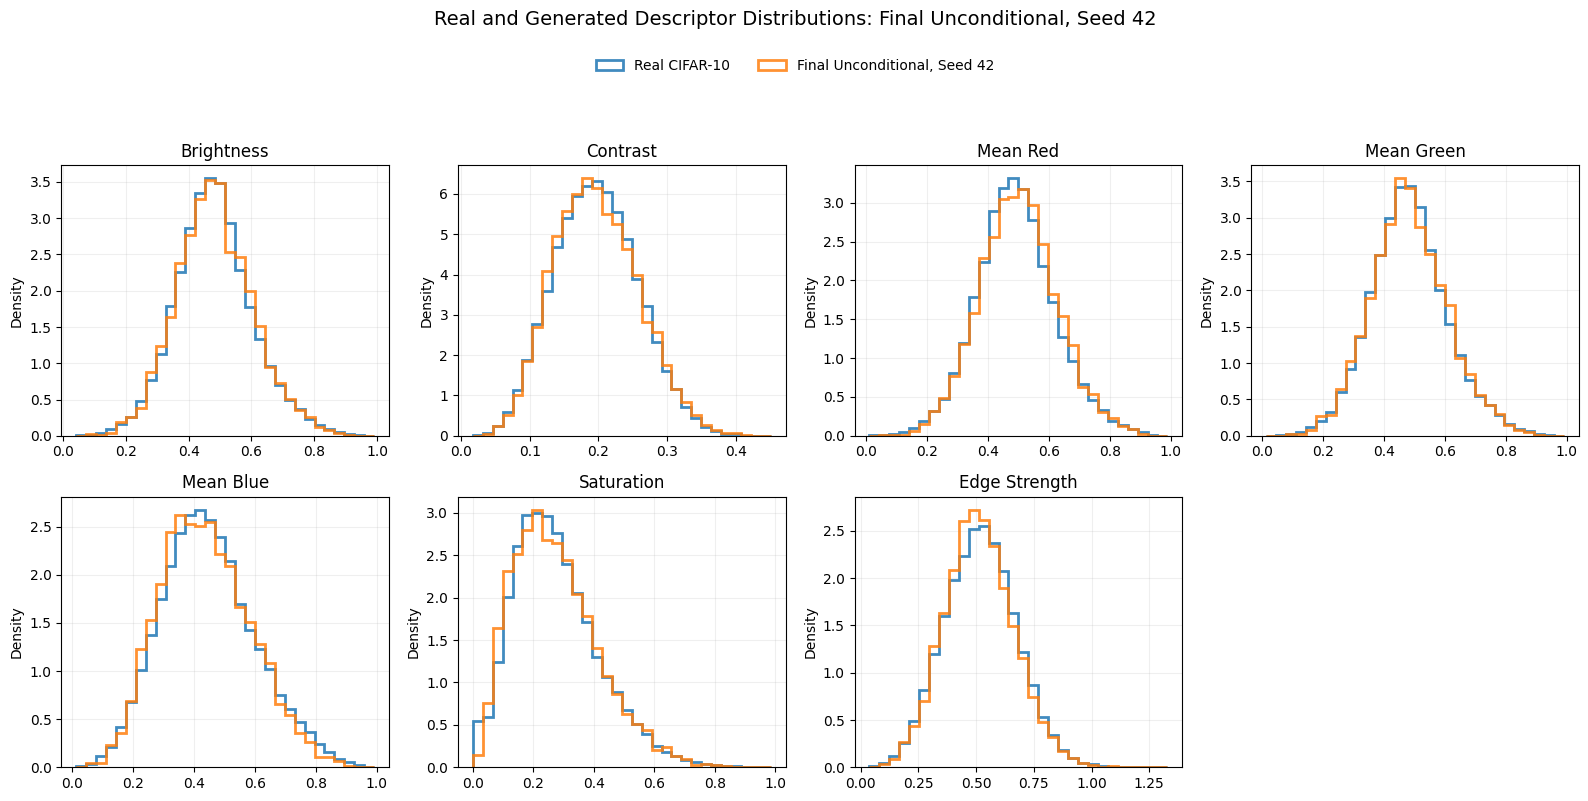

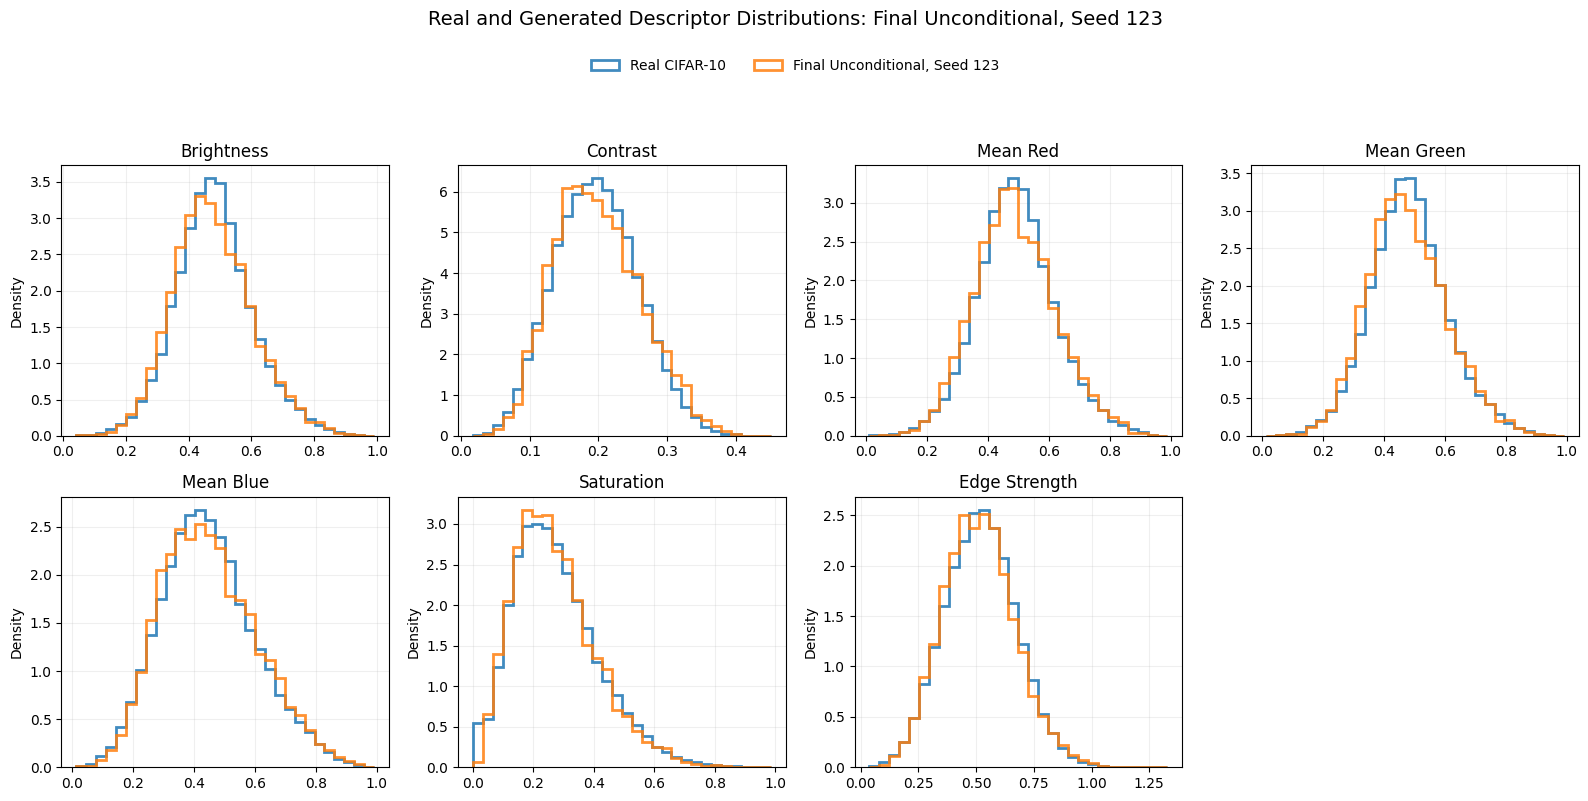

Seed-42 descriptor plot saved: [local project directory]/grids/final_unconditional_seed42_descriptor_distributions.png
Seed-123 descriptor plot saved: [local project directory]/grids/final_unconditional_seed123_descriptor_distributions.png
Protected test set remains unused.


In [82]:
required_final_unconditional_descriptor_plot_objects = [
    "final_unconditional_seed42_descriptors",
    "final_unconditional_seed123_descriptors",
    "plot_descriptor_distributions",
    "real_descriptor_df",
    "GRIDS_DIR",
]

missing_final_unconditional_descriptor_plot_objects = [
    name
    for name in required_final_unconditional_descriptor_plot_objects
    if name not in globals()
]

assert not missing_final_unconditional_descriptor_plot_objects, (
    "Incomplete descriptor-plot setup:\n"
    + "\n".join(
        missing_final_unconditional_descriptor_plot_objects
    )
)


FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed42_"
        "descriptor_distributions.png"
    )
)

FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed123_"
        "descriptor_distributions.png"
    )
)


plot_descriptor_distributions(
    real_descriptor_df,
    final_unconditional_seed42_descriptors,
    "Final Unconditional, Seed 42",
    FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_PLOT_PATH,
    bin_count=30,
)

plot_descriptor_distributions(
    real_descriptor_df,
    final_unconditional_seed123_descriptors,
    "Final Unconditional, Seed 123",
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_PLOT_PATH,
    bin_count=30,
)


print(
    "Seed-42 descriptor plot saved:",
    FINAL_UNCONDITIONAL_SEED42_DESCRIPTOR_PLOT_PATH,
)

print(
    "Seed-123 descriptor plot saved:",
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_PLOT_PATH,
)

print("Protected test set remains unused.")

In [83]:
required_final_unconditional_descriptor_closeness_objects = [
    "final_unconditional_seed42_descriptor_comparison_df",
    "final_unconditional_seed123_descriptor_comparison_df",
    "DESCRIPTOR_COLUMNS",
    "HISTORIES_DIR",
]

missing_final_unconditional_descriptor_closeness_objects = [
    name
    for name in required_final_unconditional_descriptor_closeness_objects
    if name not in globals()
]

assert not missing_final_unconditional_descriptor_closeness_objects, (
    "Incomplete descriptor-closeness setup:\n"
    + "\n".join(
        missing_final_unconditional_descriptor_closeness_objects
    )
)


seed42_mean_errors = (
    final_unconditional_seed42_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)

seed123_mean_errors = (
    final_unconditional_seed123_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)


seed42_variation_errors = np.abs(
    final_unconditional_seed42_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)

seed123_variation_errors = np.abs(
    final_unconditional_seed123_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)


mean_ties = np.isclose(
    seed42_mean_errors,
    seed123_mean_errors,
    atol=1e-12,
    rtol=0.0,
)

variation_ties = np.isclose(
    seed42_variation_errors,
    seed123_variation_errors,
    atol=1e-12,
    rtol=0.0,
)


mean_closer_labels = np.where(
    mean_ties,
    "Tie",
    np.where(
        seed123_mean_errors < seed42_mean_errors,
        "Seed 123",
        "Seed 42",
    ),
)

variation_closer_labels = np.where(
    variation_ties,
    "Tie",
    np.where(
        seed123_variation_errors
        < seed42_variation_errors,
        "Seed 123",
        "Seed 42",
    ),
)


final_unconditional_seed123_descriptor_closeness_df = (
    pd.DataFrame(
        {
            "Descriptor": DESCRIPTOR_COLUMNS,
            "Seed 42 mean error": (
                seed42_mean_errors
            ),
            "Seed 123 mean error": (
                seed123_mean_errors
            ),
            "Seed 42 variation error": (
                seed42_variation_errors
            ),
            "Seed 123 variation error": (
                seed123_variation_errors
            ),
            "Mean closer to real": (
                mean_closer_labels
            ),
            "Variation closer to real": (
                variation_closer_labels
            ),
        }
    )
)


FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_CLOSENESS_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "descriptor_closeness.csv"
    )
)


final_unconditional_seed123_descriptor_closeness_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_CLOSENESS_PATH,
    index=False,
)


display(
    final_unconditional_seed123_descriptor_closeness_df.round(4)
)


print("Mean closeness")

print(
    final_unconditional_seed123_descriptor_closeness_df[
        "Mean closer to real"
    ].value_counts()
)


print("Variation closeness")

print(
    final_unconditional_seed123_descriptor_closeness_df[
        "Variation closer to real"
    ].value_counts()
)


print(
    "Descriptor closeness saved:",
    FINAL_UNCONDITIONAL_SEED123_DESCRIPTOR_CLOSENESS_PATH,
)

print(
    "The existing matched 5,000-image pools were reused."
)

print(
    "No cross-training-seed decision has been made."
)

print("Protected test set remains unused.")

,Descriptor,Seed 42 mean error,Seed 123 mean error,Seed 42 variation error,Seed 123 variation error,Mean closer to real,Variation closer to real
0,Brightness,0.0010,0.0051,0.0097,0.0238,Seed 42,Seed 42
1,Contrast,0.0002,0.0021,0.0158,0.0453,Seed 42,Seed 42
2,Mean Red,0.0076,0.0041,0.0113,0.0317,Seed 123,Seed 42
3,Mean Green,0.0002,0.0063,0.0069,0.0194,Seed 42,Seed 42
4,Mean Blue,0.0104,0.0031,0.0393,0.0191,Seed 123,Seed 123
5,Saturation,0.0009,0.0022,0.0099,0.0492,Seed 42,Seed 42
6,Edge Strength,0.0048,0.0051,0.0353,0.0014,Seed 42,Seed 123


Mean closeness
Mean closer to real
Seed 42     5
Seed 123    2
Name: count, dtype: int64
Variation closeness
Variation closer to real
Seed 42     5
Seed 123    2
Name: count, dtype: int64
Descriptor closeness saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_descriptor_closeness.csv
The existing matched 5,000-image pools were reused.
No cross-training-seed decision has been made.
Protected test set remains unused.


#### Seed-123 Descriptor Interpretation

Both final-unconditional training seeds broadly reproduced the low-level colour, intensity and edge distributions of the real CIFAR-10 training reference.

Seed `42` showed stronger overall descriptor alignment:

- closer to the real descriptor mean for five of seven properties;
- closer to the real descriptor variation for five of seven properties.

Seed `123` was closer for the mean-red and mean-blue descriptor means. It was also closer for mean-blue and edge-strength variation, with its edge-strength standard-deviation ratio of `1.0014` almost exactly matching the real variation.

Seed `42` retained smaller errors for brightness, contrast, mean green, saturation and edge-strength means, and for brightness, contrast, mean-red, mean-green and saturation variation.

The density-normalised distributions show substantial overlap with the real training reference for both seeds. Neither seed exhibits severe descriptor compression, exaggerated spread or an abnormal photometric shift.

Descriptor evidence therefore provides a modest supporting advantage for seed `42`, but the difference is not sufficient to select a final training seed by itself. It must be combined with FID, manual quality, classifier coverage, diversity, repetition and stability evidence.

No cross-training-seed final-unconditional decision has been made.

#### Seed-42 and Seed-123 Diversity and Repetition

The matched 5,000-image pools are compared for generated-to-generated feature-space diversity and repetition.

InceptionV3 features are extracted once for both pools. Ten matched repeats then evaluate random subsets of 1,000 generated images against independently sampled real CIFAR-10 training subsets.

For each repeat, the analysis reports:

- mean and median pairwise cosine distance;
- median and minimum nearest-neighbour distance;
- generated-to-real diversity ratio;
- near-duplicate rate using the corresponding real subset's first-percentile nearest-neighbour distance.

The same generated subset indices are used for seed `42` and seed `123` within each repeat. Exact pixel duplicates are separately checked across both complete 5,000-image pools.

This evaluates generated-to-generated diversity and possible mode collapse. It is not a generated-to-training memorisation audit.

In [84]:
required_final_unconditional_diversity_objects = [
    "final_unconditional_seed42_evaluation_images",
    "final_unconditional_seed123_evaluation_images",
    "extract_inception_features",
    "compact_cosine_diversity_summary",
    "fid_feature_extractor",
    "real_fid_features",
    "FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT",
    "FINAL_UNCONDITIONAL_FID_BATCH_SIZE",
    "FINAL_UNCONDITIONAL_FID_FEATURE_DIM",
    "HISTORIES_DIR",
]

missing_final_unconditional_diversity_objects = [
    name
    for name in required_final_unconditional_diversity_objects
    if name not in globals()
]

assert not missing_final_unconditional_diversity_objects, (
    "Incomplete final-unconditional diversity setup:\n"
    + "\n".join(
        missing_final_unconditional_diversity_objects
    )
)


FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE = 1_000
FINAL_UNCONDITIONAL_DIVERSITY_REPEATS = 10
FINAL_UNCONDITIONAL_REAL_DIVERSITY_SEED = 1301
FINAL_UNCONDITIONAL_GENERATED_DIVERSITY_SEED = 1302
FINAL_UNCONDITIONAL_NEAR_DUPLICATE_PERCENTILE = 1.0


assert FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE == 1_000
assert FINAL_UNCONDITIONAL_DIVERSITY_REPEATS == 10

assert len(real_fid_features) == 50_000

for image_pool in [
    final_unconditional_seed42_evaluation_images,
    final_unconditional_seed123_evaluation_images,
]:
    assert image_pool.shape == (
        FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert image_pool.dtype == np.uint8


final_unconditional_seed42_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            final_unconditional_seed42_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FINAL_UNCONDITIONAL_FID_BATCH_SIZE,
    )
)

final_unconditional_seed123_evaluation_features = (
    extract_inception_features(
        images_uint8=(
            final_unconditional_seed123_evaluation_images
        ),
        feature_extractor=fid_feature_extractor,
        batch_size=FINAL_UNCONDITIONAL_FID_BATCH_SIZE,
    )
)


for feature_pool in [
    final_unconditional_seed42_evaluation_features,
    final_unconditional_seed123_evaluation_features,
]:
    assert feature_pool.shape == (
        FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
        FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    )

    assert np.isfinite(feature_pool).all()


print(
    "Final-unconditional diversity feature pools ready."
)

print(
    "Seed-42 features:",
    final_unconditional_seed42_evaluation_features.shape,
)

print(
    "Seed-123 features:",
    final_unconditional_seed123_evaluation_features.shape,
)

print(
    "Existing matched generated-image pools were reused."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Final-unconditional diversity feature pools ready.
Seed-42 features: (5000, 2048)
Seed-123 features: (5000, 2048)
Existing matched generated-image pools were reused.
Protected test set remains unused.


In [85]:
final_unconditional_real_diversity_rng = (
    np.random.default_rng(
        FINAL_UNCONDITIONAL_REAL_DIVERSITY_SEED
    )
)

final_unconditional_generated_diversity_rng = (
    np.random.default_rng(
        FINAL_UNCONDITIONAL_GENERATED_DIVERSITY_SEED
    )
)


final_unconditional_diversity_rows = []

# Repeat 1 is retained for the later ECDF
# and closest-generated-pair inspection.
final_unconditional_diversity_representative = None


for repeat_index in range(
    1,
    FINAL_UNCONDITIONAL_DIVERSITY_REPEATS + 1,
):
    real_indices = (
        final_unconditional_real_diversity_rng.choice(
            len(real_fid_features),
            size=FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        final_unconditional_generated_diversity_rng.choice(
            FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
            size=FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )


    real_summary = compact_cosine_diversity_summary(
        real_fid_features[real_indices]
    )

    seed42_summary = compact_cosine_diversity_summary(
        final_unconditional_seed42_evaluation_features[
            generated_indices
        ]
    )

    seed123_summary = compact_cosine_diversity_summary(
        final_unconditional_seed123_evaluation_features[
            generated_indices
        ]
    )


    near_duplicate_threshold = float(
        np.percentile(
            real_summary["nearest_distances"],
            FINAL_UNCONDITIONAL_NEAR_DUPLICATE_PERCENTILE,
        )
    )


    repeat_summaries = {
        "Real CIFAR-10": real_summary,
        "Final unconditional, seed 42": seed42_summary,
        "Final unconditional, seed 123": seed123_summary,
    }


    for configuration, summary in repeat_summaries.items():
        if configuration == "Real CIFAR-10":
            diversity_ratio = 1.0

        else:
            diversity_ratio = float(
                summary["mean_pairwise_distance"]
                / real_summary["mean_pairwise_distance"]
            )


        near_duplicate_rate = float(
            np.mean(
                summary["nearest_distances"]
                < near_duplicate_threshold
            )
            * 100.0
        )


        final_unconditional_diversity_rows.append(
            {
                "Repeat": repeat_index,
                "Configuration": configuration,
                "Feature sample count": (
                    FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE
                ),
                "Mean pairwise distance": (
                    summary["mean_pairwise_distance"]
                ),
                "Median pairwise distance": (
                    summary["median_pairwise_distance"]
                ),
                "Median nearest distance": (
                    summary["median_nearest_distance"]
                ),
                "Minimum nearest distance": (
                    summary["minimum_nearest_distance"]
                ),
                "Near-duplicate threshold": (
                    near_duplicate_threshold
                ),
                "Near-duplicate rate (%)": (
                    near_duplicate_rate
                ),
                "Diversity ratio to real": (
                    diversity_ratio
                ),
            }
        )


    if repeat_index == 1:
        final_unconditional_diversity_representative = {
            "generated_indices": generated_indices.copy(),
            "real_nearest_distances": (
                real_summary["nearest_distances"].copy()
            ),
            "seed42_nearest_distances": (
                seed42_summary["nearest_distances"].copy()
            ),
            "seed123_nearest_distances": (
                seed123_summary["nearest_distances"].copy()
            ),
            "near_duplicate_threshold": (
                near_duplicate_threshold
            ),
        }


final_unconditional_diversity_repeats_df = pd.DataFrame(
    final_unconditional_diversity_rows
)


assert len(
    final_unconditional_diversity_repeats_df
) == FINAL_UNCONDITIONAL_DIVERSITY_REPEATS * 3

assert final_unconditional_diversity_representative is not None


final_unconditional_diversity_summary_df = (
    final_unconditional_diversity_repeats_df
    .groupby(
        "Configuration",
        as_index=False,
    )
    .agg(
        mean_pairwise_distance_mean=(
            "Mean pairwise distance",
            "mean",
        ),
        mean_pairwise_distance_sd=(
            "Mean pairwise distance",
            "std",
        ),
        median_pairwise_distance_mean=(
            "Median pairwise distance",
            "mean",
        ),
        median_nearest_distance_mean=(
            "Median nearest distance",
            "mean",
        ),
        minimum_nearest_distance_mean=(
            "Minimum nearest distance",
            "mean",
        ),
        near_duplicate_rate_mean=(
            "Near-duplicate rate (%)",
            "mean",
        ),
        near_duplicate_rate_sd=(
            "Near-duplicate rate (%)",
            "std",
        ),
        diversity_ratio_mean=(
            "Diversity ratio to real",
            "mean",
        ),
        diversity_ratio_sd=(
            "Diversity ratio to real",
            "std",
        ),
    )
)


FINAL_UNCONDITIONAL_SEED123_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "diversity_repeats.csv"
    )
)

FINAL_UNCONDITIONAL_SEED123_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "diversity_summary.csv"
    )
)


final_unconditional_diversity_repeats_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_DIVERSITY_REPEATS_PATH,
    index=False,
)

final_unconditional_diversity_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_DIVERSITY_SUMMARY_PATH,
    index=False,
)


seed42_repeat_rows = (
    final_unconditional_diversity_repeats_df.loc[
        final_unconditional_diversity_repeats_df[
            "Configuration"
        ]
        == "Final unconditional, seed 42"
    ]
    .sort_values("Repeat")
)

seed123_repeat_rows = (
    final_unconditional_diversity_repeats_df.loc[
        final_unconditional_diversity_repeats_df[
            "Configuration"
        ]
        == "Final unconditional, seed 123"
    ]
    .sort_values("Repeat")
)


seed42_ratio_errors = np.abs(
    seed42_repeat_rows[
        "Diversity ratio to real"
    ].to_numpy(dtype=np.float64)
    - 1.0
)

seed123_ratio_errors = np.abs(
    seed123_repeat_rows[
        "Diversity ratio to real"
    ].to_numpy(dtype=np.float64)
    - 1.0
)


display(
    final_unconditional_diversity_summary_df.round(6)
)


print(
    "Repeats where seed 123 diversity ratio "
    "was closer to real:",
    int(
        np.sum(
            seed123_ratio_errors
            < seed42_ratio_errors
        )
    ),
    "of",
    FINAL_UNCONDITIONAL_DIVERSITY_REPEATS,
)

print(
    "Mean seed-123 improvement in absolute "
    "diversity-ratio error:",
    f"{(
        seed42_ratio_errors
        - seed123_ratio_errors
    ).mean():.6f}",
)

print(
    "Repeats where seed 123 had a lower "
    "near-duplicate rate:",
    int(
        np.sum(
            seed123_repeat_rows[
                "Near-duplicate rate (%)"
            ].to_numpy()
            < seed42_repeat_rows[
                "Near-duplicate rate (%)"
            ].to_numpy()
        )
    ),
    "of",
    FINAL_UNCONDITIONAL_DIVERSITY_REPEATS,
)

print(
    "Repeat-level results saved:",
    FINAL_UNCONDITIONAL_SEED123_DIVERSITY_REPEATS_PATH,
)

print(
    "Diversity summary saved:",
    FINAL_UNCONDITIONAL_SEED123_DIVERSITY_SUMMARY_PATH,
)

print("Protected test set remains unused.")

,Configuration,mean_pairwise_distance_mean,mean_pairwise_distance_sd,median_pairwise_distance_mean,median_nearest_distance_mean,minimum_nearest_distance_mean,near_duplicate_rate_mean,near_duplicate_rate_sd,diversity_ratio_mean,diversity_ratio_sd
0,"Final unconditional, seed 123",0.357968,0.001706,0.356759,0.200166,0.118114,0.00,0.00000,0.951659,0.007901
1,"Final unconditional, seed 42",0.358083,0.001081,0.356311,0.201618,0.112978,0.00,0.00000,0.951967,0.007493
2,Real CIFAR-10,0.376167,0.002501,0.378124,0.195888,0.061053,0.96,0.05164,1.000000,0.000000


Repeats where seed 123 diversity ratio was closer to real: 4 of 10
Mean seed-123 improvement in absolute diversity-ratio error: -0.000308
Repeats where seed 123 had a lower near-duplicate rate: 0 of 10
Repeat-level results saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_diversity_repeats.csv
Diversity summary saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_diversity_summary.csv
Protected test set remains unused.


In [86]:
final_unconditional_seed42_flat_images = (
    final_unconditional_seed42_evaluation_images.reshape(
        FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)

final_unconditional_seed123_flat_images = (
    final_unconditional_seed123_evaluation_images.reshape(
        FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT,
        -1,
    )
)


seed42_unique_count = int(
    np.unique(
        final_unconditional_seed42_flat_images,
        axis=0,
    ).shape[0]
)

seed123_unique_count = int(
    np.unique(
        final_unconditional_seed123_flat_images,
        axis=0,
    ).shape[0]
)


seed42_exact_duplicates = int(
    FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
    - seed42_unique_count
)

seed123_exact_duplicates = int(
    FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
    - seed123_unique_count
)


final_unconditional_seed123_exact_duplicate_df = (
    pd.DataFrame(
        [
            {
                "Configuration": (
                    "Final unconditional, seed 42"
                ),
                "Image sample count": (
                    FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
                ),
                "Unique images": seed42_unique_count,
                "Exact duplicates": seed42_exact_duplicates,
                "Exact-duplicate rate (%)": (
                    seed42_exact_duplicates
                    / FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
                    * 100.0
                ),
            },
            {
                "Configuration": (
                    "Final unconditional, seed 123"
                ),
                "Image sample count": (
                    FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
                ),
                "Unique images": seed123_unique_count,
                "Exact duplicates": seed123_exact_duplicates,
                "Exact-duplicate rate (%)": (
                    seed123_exact_duplicates
                    / FINAL_UNCONDITIONAL_EVALUATION_SAMPLE_COUNT
                    * 100.0
                ),
            },
        ]
    )
)


FINAL_UNCONDITIONAL_SEED123_EXACT_DUPLICATE_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "exact_duplicates.csv"
    )
)


final_unconditional_seed123_exact_duplicate_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_EXACT_DUPLICATE_PATH,
    index=False,
)


display(
    final_unconditional_seed123_exact_duplicate_df.round(6)
)


print(
    "Exact-duplicate results saved:",
    FINAL_UNCONDITIONAL_SEED123_EXACT_DUPLICATE_PATH,
)

print(
    "No generated-to-training "
    "memorisation audit was performed."
)

print("Protected test set remains unused.")


del final_unconditional_seed42_flat_images
del final_unconditional_seed123_flat_images

gc.collect()

,Configuration,Image sample count,Unique images,Exact duplicates,Exact-duplicate rate (%)
0,"Final unconditional, seed 42",5000,5000,0,0.0
1,"Final unconditional, seed 123",5000,5000,0,0.0


Exact-duplicate results saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_exact_duplicates.csv
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


22391

##### Diversity and Repetition Interpretation

The two final-unconditional training seeds showed effectively equivalent feature-space diversity.

The mean generated-to-real diversity ratios were:

- seed `42`: `0.951967 ± 0.007493`;
- seed `123`: `0.951659 ± 0.007901`.

Seed `123` was closer to the real-image ratio of `1.0` in four of ten matched repeats. Its mean improvement in absolute diversity-ratio error was `-0.000308`, indicating a negligible average advantage for seed `42`.

Both generated pools passed the repetition safeguards:

- mean near-duplicate rate: `0.00%`;
- exact duplicates among 5,000 images: `0`;
- all 5,000 images in each pool were unique.

Seed `123` had a slightly larger mean minimum nearest-neighbour distance, while seed `42` had a marginally higher mean pairwise distance. These differences are too small and inconsistent to establish a meaningful diversity advantage.

Diversity and repetition evidence therefore treats seed `42` and seed `123` as practically tied. Neither seed shows evidence of broad mode collapse or exact duplication.

This analysis concerns generated-to-generated similarity only. No generated-to-training memorisation audit was performed.

##### Nearest-Neighbour Distribution and Closest-Pair Inspection

The representative matched repeat is inspected visually using:

- empirical cumulative distributions of nearest-neighbour cosine distances;
- the ten most similar generated pairs from each training seed.

The panels are used to determine whether low feature distances correspond to exact repetition, visually indistinguishable outputs or merely related object themes.

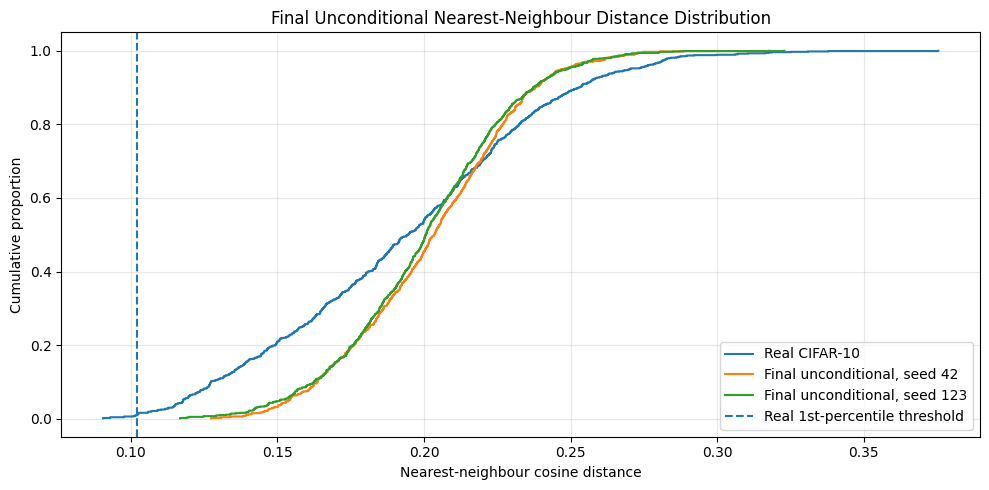

Nearest-distance plot saved: [local project directory]/grids/final_unconditional_seed42_vs_seed123_nearest_distance_ecdf.png
Near-duplicate threshold: 0.102203
Protected test set remains unused.


In [87]:
required_final_unconditional_ecdf_objects = [
    "final_unconditional_diversity_representative",
    "GRIDS_DIR",
    "np",
    "plt",
]

missing_final_unconditional_ecdf_objects = [
    name
    for name in required_final_unconditional_ecdf_objects
    if name not in globals()
]

assert not missing_final_unconditional_ecdf_objects, (
    "Incomplete final-unconditional ECDF setup:\n"
    + "\n".join(
        missing_final_unconditional_ecdf_objects
    )
)


final_unconditional_real_nearest_distances = (
    final_unconditional_diversity_representative[
        "real_nearest_distances"
    ]
)

final_unconditional_seed42_nearest_distances = (
    final_unconditional_diversity_representative[
        "seed42_nearest_distances"
    ]
)

final_unconditional_seed123_nearest_distances = (
    final_unconditional_diversity_representative[
        "seed123_nearest_distances"
    ]
)

final_unconditional_near_duplicate_threshold = float(
    final_unconditional_diversity_representative[
        "near_duplicate_threshold"
    ]
)


for nearest_distances in [
    final_unconditional_real_nearest_distances,
    final_unconditional_seed42_nearest_distances,
    final_unconditional_seed123_nearest_distances,
]:
    assert nearest_distances.shape == (
        FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE,
    )

    assert np.isfinite(
        nearest_distances
    ).all()


real_sorted_distances = np.sort(
    final_unconditional_real_nearest_distances
)

seed42_sorted_distances = np.sort(
    final_unconditional_seed42_nearest_distances
)

seed123_sorted_distances = np.sort(
    final_unconditional_seed123_nearest_distances
)


real_ecdf = np.arange(
    1,
    len(real_sorted_distances) + 1,
) / len(real_sorted_distances)

seed42_ecdf = np.arange(
    1,
    len(seed42_sorted_distances) + 1,
) / len(seed42_sorted_distances)

seed123_ecdf = np.arange(
    1,
    len(seed123_sorted_distances) + 1,
) / len(seed123_sorted_distances)


FINAL_UNCONDITIONAL_SEED123_NEAREST_DISTANCE_PLOT_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "nearest_distance_ecdf.png"
    )
)


plt.figure(
    figsize=(10, 5)
)

plt.step(
    real_sorted_distances,
    real_ecdf,
    where="post",
    label="Real CIFAR-10",
)

plt.step(
    seed42_sorted_distances,
    seed42_ecdf,
    where="post",
    label="Final unconditional, seed 42",
)

plt.step(
    seed123_sorted_distances,
    seed123_ecdf,
    where="post",
    label="Final unconditional, seed 123",
)

plt.axvline(
    final_unconditional_near_duplicate_threshold,
    linestyle="--",
    label="Real 1st-percentile threshold",
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Cumulative proportion"
)

plt.title(
    "Final Unconditional Nearest-Neighbour "
    "Distance Distribution"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FINAL_UNCONDITIONAL_SEED123_NEAREST_DISTANCE_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Nearest-distance plot saved:",
    FINAL_UNCONDITIONAL_SEED123_NEAREST_DISTANCE_PLOT_PATH,
)

print(
    "Near-duplicate threshold:",
    f"{final_unconditional_near_duplicate_threshold:.6f}",
)

print("Protected test set remains unused.")

In [88]:
required_final_unconditional_pair_objects = [
    "final_unconditional_diversity_representative",
    "final_unconditional_seed42_evaluation_images",
    "final_unconditional_seed123_evaluation_images",
    "final_unconditional_seed42_evaluation_features",
    "final_unconditional_seed123_evaluation_features",
    "FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE",
    "GRIDS_DIR",
    "HISTORIES_DIR",
    "np",
    "pd",
    "plt",
]

missing_final_unconditional_pair_objects = [
    name
    for name in required_final_unconditional_pair_objects
    if name not in globals()
]

assert not missing_final_unconditional_pair_objects, (
    "Incomplete final-unconditional closest-pair setup:\n"
    + "\n".join(
        missing_final_unconditional_pair_objects
    )
)


final_unconditional_pair_subset_indices = (
    final_unconditional_diversity_representative[
        "generated_indices"
    ]
)


assert final_unconditional_pair_subset_indices.shape == (
    FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE,
)


final_unconditional_seed42_pair_features = (
    final_unconditional_seed42_evaluation_features[
        final_unconditional_pair_subset_indices
    ]
)

final_unconditional_seed123_pair_features = (
    final_unconditional_seed123_evaluation_features[
        final_unconditional_pair_subset_indices
    ]
)


seed42_feature_norms = np.maximum(
    np.linalg.norm(
        final_unconditional_seed42_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)

seed123_feature_norms = np.maximum(
    np.linalg.norm(
        final_unconditional_seed123_pair_features,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)


seed42_normalised_features = (
    final_unconditional_seed42_pair_features
    / seed42_feature_norms
)

seed123_normalised_features = (
    final_unconditional_seed123_pair_features
    / seed123_feature_norms
)


final_unconditional_seed42_distance_matrix = np.clip(
    1.0
    - (
        seed42_normalised_features
        @ seed42_normalised_features.T
    ),
    0.0,
    2.0,
)

final_unconditional_seed123_distance_matrix = np.clip(
    1.0
    - (
        seed123_normalised_features
        @ seed123_normalised_features.T
    ),
    0.0,
    2.0,
)


np.fill_diagonal(
    final_unconditional_seed42_distance_matrix,
    np.inf,
)

np.fill_diagonal(
    final_unconditional_seed123_distance_matrix,
    np.inf,
)


upper_triangle_indices = np.triu_indices(
    FINAL_UNCONDITIONAL_DIVERSITY_SUBSET_SIZE,
    k=1,
)


FINAL_UNCONDITIONAL_CLOSEST_PAIR_COUNT = 10

FINAL_UNCONDITIONAL_SEED42_CLOSEST_PAIRS_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed42_"
        "closest_generated_pairs.png"
    )
)

FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIRS_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed123_"
        "closest_generated_pairs.png"
    )
)

FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIR_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "closest_generated_pairs.csv"
    )
)


closest_pair_rows = []


pair_panel_specifications = [
    {
        "configuration": (
            "Final unconditional, seed 42"
        ),
        "panel_title": (
            "Final Unconditional Seed-42 "
            "Most Similar Generated Pairs"
        ),
        "images": (
            final_unconditional_seed42_evaluation_images
        ),
        "distance_matrix": (
            final_unconditional_seed42_distance_matrix
        ),
        "output_path": (
            FINAL_UNCONDITIONAL_SEED42_CLOSEST_PAIRS_PATH
        ),
    },
    {
        "configuration": (
            "Final unconditional, seed 123"
        ),
        "panel_title": (
            "Final Unconditional Seed-123 "
            "Most Similar Generated Pairs"
        ),
        "images": (
            final_unconditional_seed123_evaluation_images
        ),
        "distance_matrix": (
            final_unconditional_seed123_distance_matrix
        ),
        "output_path": (
            FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIRS_PATH
        ),
    },
]


for specification in pair_panel_specifications:
    upper_triangle_distances = (
        specification["distance_matrix"][
            upper_triangle_indices
        ]
    )

    selected_pair_positions = np.argsort(
        upper_triangle_distances
    )[
        :FINAL_UNCONDITIONAL_CLOSEST_PAIR_COUNT
    ]

    first_subset_indices = (
        upper_triangle_indices[0][
            selected_pair_positions
        ]
    )

    second_subset_indices = (
        upper_triangle_indices[1][
            selected_pair_positions
        ]
    )

    selected_distances = (
        upper_triangle_distances[
            selected_pair_positions
        ]
    )


    figure, axes = plt.subplots(
        5,
        4,
        figsize=(12, 15),
    )


    for pair_offset in range(
        FINAL_UNCONDITIONAL_CLOSEST_PAIR_COUNT
    ):
        first_subset_index = int(
            first_subset_indices[pair_offset]
        )

        second_subset_index = int(
            second_subset_indices[pair_offset]
        )

        first_pool_index = int(
            final_unconditional_pair_subset_indices[
                first_subset_index
            ]
        )

        second_pool_index = int(
            final_unconditional_pair_subset_indices[
                second_subset_index
            ]
        )

        cosine_distance = float(
            selected_distances[pair_offset]
        )


        panel_row = pair_offset // 2
        panel_column = (
            pair_offset % 2
        ) * 2


        first_axis = axes[
            panel_row,
            panel_column,
        ]

        second_axis = axes[
            panel_row,
            panel_column + 1,
        ]


        first_axis.imshow(
            specification["images"][
                first_pool_index
            ]
        )

        second_axis.imshow(
            specification["images"][
                second_pool_index
            ]
        )


        first_axis.set_title(
            f"Pair {pair_offset + 1}A",
            fontsize=10,
        )

        second_axis.set_title(
            (
                f"Pair {pair_offset + 1}B\n"
                f"Distance: {cosine_distance:.4f}"
            ),
            fontsize=10,
        )


        first_axis.axis("off")
        second_axis.axis("off")


        closest_pair_rows.append(
            {
                "Configuration": (
                    specification["configuration"]
                ),
                "Pair": pair_offset + 1,
                "First subset index": (
                    first_subset_index
                ),
                "Second subset index": (
                    second_subset_index
                ),
                "First pool index": (
                    first_pool_index
                ),
                "Second pool index": (
                    second_pool_index
                ),
                "Cosine distance": (
                    cosine_distance
                ),
            }
        )


    figure.suptitle(
        specification["panel_title"],
        fontsize=16,
    )

    figure.tight_layout(
        rect=(0, 0, 1, 0.97)
    )

    figure.savefig(
        specification["output_path"],
        dpi=170,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


final_unconditional_seed123_closest_pairs_df = (
    pd.DataFrame(
        closest_pair_rows
    )
)


assert len(
    final_unconditional_seed123_closest_pairs_df
) == 20

assert np.isfinite(
    final_unconditional_seed123_closest_pairs_df[
        "Cosine distance"
    ]
).all()


final_unconditional_seed123_closest_pairs_df.to_csv(
    FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIR_RESULTS_PATH,
    index=False,
)


display(
    final_unconditional_seed123_closest_pairs_df.round(6)
)


print(
    "Seed-42 closest-pair panel saved:",
    FINAL_UNCONDITIONAL_SEED42_CLOSEST_PAIRS_PATH,
)

print(
    "Seed-123 closest-pair panel saved:",
    FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIRS_PATH,
)

print(
    "Closest-pair results saved:",
    FINAL_UNCONDITIONAL_SEED123_CLOSEST_PAIR_RESULTS_PATH,
)

print(
    "The same matched 1,000-image subset "
    "was used for both training seeds."
)

print(
    "No generated-to-training "
    "memorisation audit was performed."
)

print("Protected test set remains unused.")

,Configuration,Pair,First subset index,Second subset index,First pool index,Second pool index,Cosine distance
0,"Final unconditional, seed 42",1,291,506,3906,3368,0.127408
1,"Final unconditional, seed 42",2,90,283,4665,2064,0.130829
2,"Final unconditional, seed 42",3,697,966,357,46,0.134076
3,"Final unconditional, seed 42",4,90,506,4665,3368,0.137351
4,"Final unconditional, seed 42",5,129,882,2902,3133,0.138325
5,"Final unconditional, seed 42",6,323,470,2273,4513,0.139319
6,"Final unconditional, seed 42",7,90,576,4665,4052,0.140004
7,"Final unconditional, seed 42",8,675,882,3457,3133,0.140085
8,"Final unconditional, seed 42",9,610,628,4664,4039,0.141157
9,"Final unconditional, seed 42",10,391,470,4808,4513,0.141259


Seed-42 closest-pair panel saved: [local project directory]/grids/final_unconditional_seed42_closest_generated_pairs.png
Seed-123 closest-pair panel saved: [local project directory]/grids/final_unconditional_seed123_closest_generated_pairs.png
Closest-pair results saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_closest_generated_pairs.csv
The same matched 1,000-image subset was used for both training seeds.
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


##### Nearest-Neighbour Interpretation

The nearest-neighbour distance distributions for seeds `42` and `123` overlap closely and remain well above the real-image first-percentile near-duplicate threshold for almost the entire representative subset.

The closest-pair panels show recurring themes, particularly vehicles and similarly posed animals, but not exact or visually indistinguishable duplicates. Some images appear in more than one pair because they have multiple nearby neighbours in feature space.

Seed `123` produced several tighter vehicle-related clusters than seed `42`, with its closest observed pair distance falling from approximately `0.1274` to `0.1168`. This remains above the near-duplicate threshold and is not accompanied by exact duplication or a reduced overall diversity ratio.

The visual inspection therefore confirms the quantitative result: both seeds pass the repetition safeguard, and neither shows broad mode collapse.

#### Seed-42 and Seed-123 Stability and Compute Consolidation

The two completed final-unconditional training seeds are compared using their complete 100-epoch histories.

Because both runs use the same architecture, batch size, update ratio and target epoch count, the comparison focuses on:

- final-20 generator and discriminator loss variability;
- mean real-image and generated-image discriminator scores;
- score separation during epochs 61–80 and 81–100;
- late-training score-separation change;
- total recorded training time;
- identical parameter counts and update exposure.

Losses and discriminator scores remain diagnostic only. They are not used as independent evidence of generated-image quality.

In [91]:
required_final_unconditional_stability_plot_objects = [
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "plot_dcgan_history_comparison",
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
]

missing_final_unconditional_stability_plot_objects = [
    name
    for name in required_final_unconditional_stability_plot_objects
    if name not in globals()
]

assert not missing_final_unconditional_stability_plot_objects, (
    "Incomplete final-unconditional stability-plot setup:\n"
    + "\n".join(
        missing_final_unconditional_stability_plot_objects
    )
)


FINAL_UNCONDITIONAL_SEED42_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

final_unconditional_seed42_history_path = (
    HISTORIES_DIR
    / f"{FINAL_UNCONDITIONAL_SEED42_RUN_ID}.csv"
)

final_unconditional_seed123_history_path = (
    HISTORIES_DIR
    / f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}.csv"
)


assert final_unconditional_seed42_history_path.is_file()
assert final_unconditional_seed123_history_path.is_file()


FINAL_UNCONDITIONAL_SEED42_VS_SEED123_TRAJECTORY_PATH = (
    GRIDS_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "training_trajectories.png"
    )
)


plot_dcgan_history_comparison(
    history_specs=[
        {
            "label": (
                "Final unconditional, seed 42"
            ),
            "history_path": (
                final_unconditional_seed42_history_path
            ),
        },
        {
            "label": (
                "Final unconditional, seed 123"
            ),
            "history_path": (
                final_unconditional_seed123_history_path
            ),
        },
    ],
    title=(
        "Final Unconditional Seed-42 and "
        "Seed-123 Training Trajectories"
    ),
    output_path=(
        FINAL_UNCONDITIONAL_SEED42_VS_SEED123_TRAJECTORY_PATH
    ),
)


print(
    "Matched trajectory plot saved:",
    FINAL_UNCONDITIONAL_SEED42_VS_SEED123_TRAJECTORY_PATH,
)

print(
    "Losses and discriminator scores "
    "remain diagnostic only."
)

print("Protected test set remains unused.")

Matched trajectory plot saved: [local project directory]/grids/final_unconditional_seed42_vs_seed123_training_trajectories.png
Losses and discriminator scores remain diagnostic only.
Protected test set remains unused.


In [92]:
required_final_unconditional_stability_objects = [
    "HISTORIES_DIR",
    "FINAL_UNCONDITIONAL_SEED123_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "pd",
    "np",
]

missing_final_unconditional_stability_objects = [
    name
    for name in required_final_unconditional_stability_objects
    if name not in globals()
]

assert not missing_final_unconditional_stability_objects, (
    "Incomplete final-unconditional stability setup:\n"
    + "\n".join(
        missing_final_unconditional_stability_objects
    )
)


final_unconditional_stability_specs = [
    {
        "Configuration": (
            "Final unconditional, seed 42"
        ),
        "Run ID": (
            FINAL_UNCONDITIONAL_SEED42_RUN_ID
        ),
        "Training seed": 42,
        "Selected epoch": 100,
    },
    {
        "Configuration": (
            "Final unconditional, seed 123"
        ),
        "Run ID": (
            FINAL_UNCONDITIONAL_SEED123_RUN_ID
        ),
        "Training seed": 123,
        "Selected epoch": (
            FINAL_UNCONDITIONAL_SEED123_SELECTED_EPOCH
        ),
    },
]


required_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


final_unconditional_stability_rows = []


for specification in final_unconditional_stability_specs:
    history_path = (
        HISTORIES_DIR
        / f"{specification['Run ID']}.csv"
    )

    assert history_path.is_file()


    history_df = (
        pd.read_csv(history_path)
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    missing_history_columns = [
        column
        for column in required_history_columns
        if column not in history_df.columns
    ]

    assert not missing_history_columns, (
        f"{specification['Run ID']} history is missing:\n"
        + "\n".join(missing_history_columns)
    )


    assert len(history_df) == 100

    assert np.array_equal(
        history_df["epoch"].to_numpy(
            dtype=np.int64
        ),
        np.arange(1, 101),
    )

    assert np.isfinite(
        history_df[
            required_history_columns
        ].to_numpy(dtype=np.float64)
    ).all()


    history_df["score_separation"] = (
        history_df["real_score"]
        - history_df["fake_score"]
    )


    epochs_61_to_80_df = history_df.loc[
        history_df["epoch"].between(
            61,
            80,
        )
    ]

    epochs_81_to_100_df = history_df.loc[
        history_df["epoch"].between(
            81,
            100,
        )
    ]


    assert len(epochs_61_to_80_df) == 20
    assert len(epochs_81_to_100_df) == 20


    earlier_separation = float(
        epochs_61_to_80_df[
            "score_separation"
        ].mean()
    )

    final_separation = float(
        epochs_81_to_100_df[
            "score_separation"
        ].mean()
    )


    final_unconditional_stability_rows.append(
        {
            **specification,
            "Epochs completed": 100,
            "Batches per epoch": 782,
            "Generator updates": 78_200,
            "Discriminator updates": 78_200,
            "Generator parameters": (
                CURRENT_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CURRENT_DISCRIMINATOR_PARAMETERS
            ),
            "Training time minutes": float(
                history_df[
                    "epoch_time_seconds"
                ].sum()
                / 60.0
            ),
            "Final-20 G loss mean": float(
                epochs_81_to_100_df[
                    "generator_loss"
                ].mean()
            ),
            "Final-20 G loss SD": float(
                epochs_81_to_100_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Final-20 D loss mean": float(
                epochs_81_to_100_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Final-20 D loss SD": float(
                epochs_81_to_100_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Final-20 real score mean": float(
                epochs_81_to_100_df[
                    "real_score"
                ].mean()
            ),
            "Final-20 fake score mean": float(
                epochs_81_to_100_df[
                    "fake_score"
                ].mean()
            ),
            "Epochs 61–80 score separation": (
                earlier_separation
            ),
            "Final-20 score separation": (
                final_separation
            ),
            "Late score-separation change": float(
                final_separation
                - earlier_separation
            ),
            "Finite history": True,
        }
    )


final_unconditional_seed42_vs_seed123_stability_df = (
    pd.DataFrame(
        final_unconditional_stability_rows
    )
)


FINAL_UNCONDITIONAL_SEED42_VS_SEED123_STABILITY_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "stability_compute.csv"
    )
)


final_unconditional_seed42_vs_seed123_stability_df.to_csv(
    FINAL_UNCONDITIONAL_SEED42_VS_SEED123_STABILITY_PATH,
    index=False,
)


seed42_stability_row = (
    final_unconditional_seed42_vs_seed123_stability_df
    .loc[
        final_unconditional_seed42_vs_seed123_stability_df[
            "Training seed"
        ]
        == 42
    ]
    .iloc[0]
)

seed123_stability_row = (
    final_unconditional_seed42_vs_seed123_stability_df
    .loc[
        final_unconditional_seed42_vs_seed123_stability_df[
            "Training seed"
        ]
        == 123
    ]
    .iloc[0]
)


seed123_minus_seed42_runtime = float(
    seed123_stability_row[
        "Training time minutes"
    ]
    - seed42_stability_row[
        "Training time minutes"
    ]
)

seed123_minus_seed42_separation = float(
    seed123_stability_row[
        "Final-20 score separation"
    ]
    - seed42_stability_row[
        "Final-20 score separation"
    ]
)


display(
    final_unconditional_seed42_vs_seed123_stability_df.round(4)
)


print(
    "Seed 123 minus seed 42 runtime:",
    f"{seed123_minus_seed42_runtime:.4f}",
    "minutes",
)

print(
    "Seed 123 minus seed 42 final-20 "
    "score separation:",
    f"{seed123_minus_seed42_separation:.4f}",
)

print(
    "Stability and compute summary saved:",
    FINAL_UNCONDITIONAL_SEED42_VS_SEED123_STABILITY_PATH,
)

print(
    "No image-quality conclusion is made "
    "from losses or discriminator scores alone."
)

print(
    "No cross-training-seed final-unconditional "
    "decision has been made."
)

print("Protected test set remains unused.")

,Configuration,Run ID,Training seed,Selected epoch,Epochs completed,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,...,Final-20 G loss mean,Final-20 G loss SD,Final-20 D loss mean,Final-20 D loss SD,Final-20 real score mean,Final-20 fake score mean,Epochs 61–80 score separation,Final-20 score separation,Late score-separation change,Finite history
0,"Final unconditional, seed 42",G08_augmentation_fliptranslation_seed42,42,100,100,782,78200,78200,1085187,664129,...,2.9404,0.1009,0.2166,0.0099,0.8503,0.1495,0.6577,0.7008,0.0431,True
1,"Final unconditional, seed 123",G09_final_unconditional_fliptranslation_seed123,123,90,100,782,78200,78200,1085187,664129,...,2.8504,0.0867,0.2221,0.0126,0.8460,0.1538,0.6522,0.6923,0.0401,True


Seed 123 minus seed 42 runtime: 0.6625 minutes
Seed 123 minus seed 42 final-20 score separation: -0.0085
Stability and compute summary saved: [local project directory]/histories/final_unconditional_seed42_vs_seed123_stability_compute.csv
No image-quality conclusion is made from losses or discriminator scores alone.
No cross-training-seed final-unconditional decision has been made.
Protected test set remains unused.


#### Seed-42 and Seed-123 Stability Interpretation

The seed-42 and seed-123 final-unconditional runs followed closely matched training trajectories.

Both completed:

- 100 epochs;
- 782 batches per epoch;
- 78,200 generator updates;
- 78,200 discriminator updates;
- the same generator and discriminator architectures.

Seed `123` required only `0.6625` additional training minutes. Its final-20 mean score separation was `0.0085` lower than seed `42`, while the two trajectories remained closely aligned throughout training.

Seed `123` had slightly lower final-20 generator-loss variability, whereas seed `42` had slightly lower discriminator-loss variability. These differences are small and do not establish a meaningful stability advantage for either run.

Both histories remained finite and smooth, with no sudden collapse, divergence or late-training instability. Stability and compute evidence therefore treats seeds `42` and `123` as practically equivalent.

No image-quality conclusion is inferred from losses or discriminator scores alone.

### 12.2 Independent Seed-456 Training

A third independent final-unconditional run is trained using seed `456`.

This run changes only the complete training seed and the corresponding augmentation randomness. It retains:

- the original selected DCGAN architecture;
- latent dimension `100`;
- batch size `64`;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- one discriminator update followed by one generator update;
- symmetric horizontal flipping and two-pixel translation;
- 100 training epochs;
- the same checkpoint, milestone and fixed-grid schedule.

The augmentation policy uses seed `456`, while the translation layer consequently uses seed `457`.

Seed `456` is a lean training-seed robustness confirmation. After training, it will receive artifact validation, milestone FID, progression and stability review, checkpoint selection, repeated FID and one uncurated visual-veto grid. The deeper coverage, descriptor and diversity package will only be triggered if seed `456` materially contradicts the first two training seeds.

In [94]:
required_final_unconditional_seed456_objects = [
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "REQUIRED_DCGAN_FAMILY_CONFIG_KEYS",
    "build_dcgan_generator",
    "make_augmented_discriminator_builder",
    "run_dcgan_family",
    "reset_run_seed",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
]

missing_final_unconditional_seed456_objects = [
    name
    for name in required_final_unconditional_seed456_objects
    if name not in globals()
]

assert not missing_final_unconditional_seed456_objects, (
    "Incomplete seed-456 training setup:\n"
    + "\n".join(
        missing_final_unconditional_seed456_objects
    )
)


FINAL_UNCONDITIONAL_FAMILY_NAME = (
    "Final unconditional GAN"
)

FINAL_UNCONDITIONAL_SEED456_RUN_ID = (
    "G09_final_unconditional_fliptranslation_seed456"
)

FINAL_UNCONDITIONAL_SEED456_LABEL = (
    "Final Unconditional DCGAN, "
    "Flip + Translation, Seed 456"
)

FINAL_UNCONDITIONAL_SEED456_TRAINING_SEED = 456

FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED = 456

FINAL_UNCONDITIONAL_SEED456_TRANSLATION_SEED = 457

FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

FINAL_UNCONDITIONAL_SEED456_CHECKPOINT_INTERVAL = 10


assert FINAL_UNCONDITIONAL_SEED456_TRAINING_SEED == 456

assert (
    FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED
    == 456
)

assert (
    FINAL_UNCONDITIONAL_SEED456_TRANSLATION_SEED
    == FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED + 1
)

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64

assert FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert (
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert x_train_gan.shape == (
    50_000,
    32,
    32,
    3,
)

assert x_train_gan.dtype == np.float32

assert np.isclose(
    x_train_gan.min(),
    -1.0,
)

assert np.isclose(
    x_train_gan.max(),
    1.0,
)


FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER = (
    make_augmented_discriminator_builder(
        policy_name="flip_translation",
        augmentation_seed=(
            FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED
        ),
    )
)


FINAL_UNCONDITIONAL_SEED456_CONFIGURATIONS = [
    {
        "run_id": (
            FINAL_UNCONDITIONAL_SEED456_RUN_ID
        ),
        "configuration_label": (
            FINAL_UNCONDITIONAL_SEED456_LABEL
        ),
        "main_change": (
            "Independent seed-456 confirmation "
            "of the final-unconditional "
            "flip-and-translation configuration"
        ),
        "training_seed": (
            FINAL_UNCONDITIONAL_SEED456_TRAINING_SEED
        ),
        "latent_dim": CURRENT_LATENT_DIM,
        "batch_size": CURRENT_BATCH_SIZE,
        "generator_builder": (
            build_dcgan_generator
        ),
        "discriminator_builder": (
            FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER
        ),
        "generator_learning_rate": (
            CURRENT_GENERATOR_LR
        ),
        "discriminator_learning_rate": (
            CURRENT_DISCRIMINATOR_LR
        ),
        "beta_1": CURRENT_BETA_1,
        "beta_2": CURRENT_BETA_2,
    }
]


assert len(
    FINAL_UNCONDITIONAL_SEED456_CONFIGURATIONS
) == 1


seed456_configuration = (
    FINAL_UNCONDITIONAL_SEED456_CONFIGURATIONS[0]
)

missing_seed456_configuration_keys = [
    key
    for key in REQUIRED_DCGAN_FAMILY_CONFIG_KEYS
    if key not in seed456_configuration
]

assert not missing_seed456_configuration_keys, (
    "Seed-456 configuration is missing:\n"
    + "\n".join(
        missing_seed456_configuration_keys
    )
)

assert (
    seed456_configuration["training_seed"]
    == 456
)

assert (
    seed456_configuration["generator_builder"]
    is build_dcgan_generator
)

assert callable(
    seed456_configuration["discriminator_builder"]
)

In [95]:
keras.backend.clear_session()

reset_run_seed(
    FINAL_UNCONDITIONAL_SEED456_TRAINING_SEED
)


seed456_probe_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

seed456_probe_discriminator = (
    FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER()
)


assert (
    seed456_probe_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    seed456_probe_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


final_unconditional_seed456_plan_df = pd.DataFrame(
    [
        {
            "Run ID": (
                FINAL_UNCONDITIONAL_SEED456_RUN_ID
            ),
            "Training seed": (
                FINAL_UNCONDITIONAL_SEED456_TRAINING_SEED
            ),
            "Augmentation": (
                "Horizontal flip + translation"
            ),
            "Augmentation seed": (
                FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED
            ),
            "Translation-layer seed": (
                FINAL_UNCONDITIONAL_SEED456_TRANSLATION_SEED
            ),
            "Generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Latent dimension": (
                CURRENT_LATENT_DIM
            ),
            "Batch size": (
                CURRENT_BATCH_SIZE
            ),
            "Epochs": (
                FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS
            ),
            "Training action": (
                "Fresh train or resume matching run"
            ),
        }
    ]
)


display(
    final_unconditional_seed456_plan_df
)


print(
    "Seed-456 final-unconditional "
    "configuration validated."
)

print(
    "Generator parameters:",
    seed456_probe_generator.count_params(),
)

print(
    "Discriminator parameters:",
    seed456_probe_discriminator.count_params(),
)

print(
    "Augmentation seed:",
    FINAL_UNCONDITIONAL_SEED456_AUGMENTATION_SEED,
)

print(
    "Translation-layer seed:",
    FINAL_UNCONDITIONAL_SEED456_TRANSLATION_SEED,
)

print(
    "Seeds 42 and 123 will not be retrained."
)

print("Protected test set remains unused.")


del seed456_probe_generator
del seed456_probe_discriminator

keras.backend.clear_session()
gc.collect()

,Run ID,Training seed,Augmentation,Augmentation seed,Translation-layer seed,Generator LR,Discriminator LR,Latent dimension,Batch size,Epochs,Training action
0,G09_final_unconditional_fliptranslation_seed456,456,Horizontal flip + translation,456,457,0.0002,0.0002,100,64,100,Fresh train or resume matching run


Seed-456 final-unconditional configuration validated.
Generator parameters: 1085187
Discriminator parameters: 664129
Augmentation seed: 456
Translation-layer seed: 457
Seeds 42 and 123 will not be retrained.
Protected test set remains unused.


0

In [96]:
keras.backend.clear_session()


final_unconditional_seed456_training_df = (
    run_dcgan_family(
        family_name=(
            FINAL_UNCONDITIONAL_FAMILY_NAME
        ),
        configurations=(
            FINAL_UNCONDITIONAL_SEED456_CONFIGURATIONS
        ),
        training_images=x_train_gan,
        target_epochs=(
            FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            FINAL_UNCONDITIONAL_SEED456_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        max_to_keep=3,
    )
)


display(
    final_unconditional_seed456_training_df[
        [
            "run_id",
            "configuration_label",
            "action",
            "epochs_completed",
            "batches_per_epoch",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


assert len(
    final_unconditional_seed456_training_df
) == 1

assert int(
    final_unconditional_seed456_training_df[
        "epochs_completed"
    ].iloc[0]
) == 100

assert int(
    final_unconditional_seed456_training_df[
        "batches_per_epoch"
    ].iloc[0]
) == 782

assert int(
    final_unconditional_seed456_training_df[
        "generator_updates"
    ].iloc[0]
) == 78_200

assert int(
    final_unconditional_seed456_training_df[
        "discriminator_updates"
    ].iloc[0]
) == 78_200


print(
    "Seed-456 final-unconditional "
    "training call completed."
)

print(
    "No seed-456 checkpoint has "
    "been selected."
)

print(
    "No cross-training-seed final "
    "decision has been made."
)

print("Protected test set remains unused.")

Declared family: Final unconditional GAN


,Order,Run ID,Configuration,Main change,Training seed,Latent dimension,Batch size,Generator LR,Discriminator LR,Beta 1,Beta 2
0,1,G09_final_unconditional_fliptranslation_seed456,"Final Unconditional DCGAN, Flip + Translation,...",Independent seed-456 confirmation of the final...,456,100,64,0.0002,0.0002,0.5,0.999


Candidate list validated before training.
Unexpected errors will stop the family immediately.

Family configuration 1/1
Run ID: G09_final_unconditional_fliptranslation_seed456
Configuration: Final Unconditional DCGAN, Flip + Translation, Seed 456
Main change: Independent seed-456 confirmation of the final-unconditional flip-and-translation configuration
Training new run G09_final_unconditional_fliptranslation_seed456 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.7406 | D loss: 0.1703 | Real: 0.8879 | Fake: 0.1101 | Time: 18.5s
Epoch 002/100 | G loss: 0.6086 | D loss: 0.1910 | Real: 0.8715 | Fake: 0.1256 | Time: 13.8s
Epoch 003/100 | G loss: 0.1971 | D loss: 0.0682 | Real: 0.9561 | Fake: 0.0427 | Time: 13.8s
Epoch 004/100 | G loss: 0.2598 | D loss: 0.1254 | Real: 0.9227 | Fake: 0.0773 | Time: 13.8s
Epoch 005/100 | G loss: 0.3120 | D loss: 0.1366 | Real: 0.9081 | Fake: 0.0904 | Time: 13.7s
Epoch 006/100 | G loss: 0.1765 | D loss: 0.1044 | Real: 0.9349 | Fake: 0.0648 | Time: 13.6s
Epoch 

,run_id,configuration_label,action,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G09_final_unconditional_fliptranslation_seed456,"Final Unconditional DCGAN, Flip + Translation,...",trained_new,100,782,78200,78200,1085187,664129,23.0663


Seed-456 final-unconditional training call completed.
No seed-456 checkpoint has been selected.
No cross-training-seed final decision has been made.
Protected test set remains unused.


#### Seed-456 Training Artifact Audit

The completed seed-456 run is audited before checkpoint evaluation.

The audit verifies:

- a complete finite 100-epoch history;
- 782 batches per epoch;
- 78,200 generator and discriminator updates;
- progression grids every 10 epochs;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100;
- a recoverable epoch-100 checkpoint;
- unchanged model parameter counts;
- recorded training time.

Passing this audit confirms that the run is complete and reproducible enough to proceed to milestone development FID. It does not select a checkpoint.

In [97]:
required_seed456_audit_objects = [
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS",
    "FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "pd",
    "np",
    "tf",
]

missing_seed456_audit_objects = [
    name
    for name in required_seed456_audit_objects
    if name not in globals()
]

assert not missing_seed456_audit_objects, (
    "Incomplete seed-456 artifact-audit setup:\n"
    + "\n".join(
        missing_seed456_audit_objects
    )
)


seed456_history_path = (
    HISTORIES_DIR
    / f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}.csv"
)

seed456_checkpoint_dir = (
    CHECKPOINTS_DIR
    / FINAL_UNCONDITIONAL_SEED456_RUN_ID
)


assert seed456_history_path.is_file(), (
    "Missing seed-456 history:\n"
    f"{seed456_history_path}"
)

assert seed456_checkpoint_dir.is_dir(), (
    "Missing seed-456 checkpoint directory:\n"
    f"{seed456_checkpoint_dir}"
)


seed456_history_df = (
    pd.read_csv(seed456_history_path)
    .sort_values("epoch")
    .reset_index(drop=True)
)


seed456_required_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

seed456_missing_history_columns = [
    column
    for column in seed456_required_history_columns
    if column not in seed456_history_df.columns
]

assert not seed456_missing_history_columns, (
    "Seed-456 history is missing:\n"
    + "\n".join(seed456_missing_history_columns)
)


assert len(seed456_history_df) == 100

assert np.array_equal(
    seed456_history_df["epoch"].to_numpy(
        dtype=np.int64
    ),
    np.arange(1, 101),
)

assert np.isfinite(
    seed456_history_df[
        seed456_required_history_columns
    ].to_numpy(dtype=np.float64)
).all()


seed456_expected_progression_epochs = tuple(
    range(
        10,
        FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS + 1,
        10,
    )
)

seed456_progression_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in seed456_expected_progression_epochs
}


seed456_generator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch in (
        FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
    )
}

seed456_discriminator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch in (
        FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
    )
}


for epoch, path in seed456_progression_paths.items():
    assert path.is_file(), (
        f"Missing epoch-{epoch} progression grid:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


for epoch, path in (
    seed456_generator_milestone_paths.items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} generator weights:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


for epoch, path in (
    seed456_discriminator_milestone_paths.items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} discriminator weights:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


seed456_latest_checkpoint = tf.train.latest_checkpoint(
    str(seed456_checkpoint_dir)
)

assert seed456_latest_checkpoint is not None, (
    "No recoverable seed-456 checkpoint found."
)

seed456_latest_checkpoint_epoch = int(
    seed456_latest_checkpoint.rsplit("-", 1)[-1]
)

assert seed456_latest_checkpoint_epoch == 100


seed456_expected_batches_per_epoch = int(
    np.ceil(
        len(x_train_gan)
        / CURRENT_BATCH_SIZE
    )
)

seed456_expected_updates = int(
    seed456_expected_batches_per_epoch
    * FINAL_UNCONDITIONAL_SEED456_TARGET_EPOCHS
)


assert seed456_expected_batches_per_epoch == 782
assert seed456_expected_updates == 78_200


seed456_training_time_minutes = float(
    seed456_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


print("Seed-456 saved artifacts validated.")

print(
    "History rows:",
    len(seed456_history_df),
)

print(
    "Latest checkpoint:",
    seed456_latest_checkpoint,
)

print(
    "Progression grids:",
    len(seed456_progression_paths),
)

print(
    "Generator milestones:",
    len(seed456_generator_milestone_paths),
)

print(
    "Discriminator milestones:",
    len(seed456_discriminator_milestone_paths),
)

print(
    "Recorded training time:",
    f"{seed456_training_time_minutes:.4f}",
    "minutes",
)

Seed-456 saved artifacts validated.
History rows: 100
Latest checkpoint: [local project directory]/checkpoints/G09_final_unconditional_fliptranslation_seed456/ckpt-100
Progression grids: 10
Generator milestones: 4
Discriminator milestones: 4
Recorded training time: 23.0663 minutes


In [98]:
final_unconditional_seed456_artifact_audit_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED456_RUN_ID
                ),
                "Status": "completed",
                "History rows": int(
                    len(seed456_history_df)
                ),
                "Checkpoint epoch": int(
                    seed456_latest_checkpoint_epoch
                ),
                "Progression grids": int(
                    len(seed456_progression_paths)
                ),
                "Generator milestones": int(
                    len(
                        seed456_generator_milestone_paths
                    )
                ),
                "Discriminator milestones": int(
                    len(
                        seed456_discriminator_milestone_paths
                    )
                ),
                "Batches per epoch": int(
                    seed456_expected_batches_per_epoch
                ),
                "Generator updates": int(
                    seed456_expected_updates
                ),
                "Discriminator updates": int(
                    seed456_expected_updates
                ),
                "Generator parameters": int(
                    CURRENT_GENERATOR_PARAMETERS
                ),
                "Discriminator parameters": int(
                    CURRENT_DISCRIMINATOR_PARAMETERS
                ),
                "Finite history": True,
                "Training time minutes": (
                    seed456_training_time_minutes
                ),
            }
        ]
    )
)


FINAL_UNCONDITIONAL_SEED456_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed456_artifact_audit.csv"
)


final_unconditional_seed456_artifact_audit_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    final_unconditional_seed456_artifact_audit_df.round(4)
)


print("Seed-456 artifact audit passed.")

print(
    "Artifact audit saved:",
    FINAL_UNCONDITIONAL_SEED456_ARTIFACT_AUDIT_PATH,
)

print(
    "Checkpoint selection has not yet been performed."
)

print(
    "No cross-training-seed final decision "
    "has been made."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,Finite history,Training time minutes
0,G09_final_unconditional_fliptranslation_seed456,completed,100,100,10,4,4,782,78200,78200,1085187,664129,True,23.0663


Seed-456 artifact audit passed.
Artifact audit saved: [local project directory]/histories/final_unconditional_seed456_artifact_audit.csv
Checkpoint selection has not yet been performed.
No cross-training-seed final decision has been made.
Protected test set remains unused.


#### Seed-456 Milestone Development FID

The saved seed-456 generator milestones at epochs `50`, `70`, `90` and `100` are evaluated against the protected CIFAR-10 training reference.

Each milestone uses:

- 5,000 generated images;
- fixed FID seed `1001`;
- the same frozen InceptionV3 feature extractor;
- the same 50,000-image real training feature reference;
- ordinary, unaugmented generator outputs.

The lowest milestone FID is provisional only. The corresponding fixed-seed progression and training trajectory must be inspected before the checkpoint is selected.

In [100]:
required_seed456_milestone_fid_objects = [
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS",
    "seed456_generator_milestone_paths",
    "CURRENT_LATENT_DIM",
    "FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT",
    "FINAL_UNCONDITIONAL_FID_BATCH_SIZE",
    "FINAL_UNCONDITIONAL_FID_FEATURE_DIM",
    "FINAL_UNCONDITIONAL_MILESTONE_FID_SEED",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "HISTORIES_DIR",
]

missing_seed456_milestone_fid_objects = [
    name
    for name in required_seed456_milestone_fid_objects
    if name not in globals()
]

assert not missing_seed456_milestone_fid_objects, (
    "Incomplete seed-456 milestone-FID setup:\n"
    + "\n".join(
        missing_seed456_milestone_fid_objects
    )
)


assert (
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_FID_FEATURE_DIM == 2_048
assert FINAL_UNCONDITIONAL_MILESTONE_FID_SEED == 1001
assert CURRENT_LATENT_DIM == 100


for epoch in (
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
):
    milestone_path = (
        seed456_generator_milestone_paths[epoch]
    )

    assert milestone_path.is_file(), (
        f"Missing epoch-{epoch} generator weights:\n"
        f"{milestone_path}"
    )

    assert milestone_path.stat().st_size > 0


assert np.asarray(
    real_fid_mean
).shape == (
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
)

assert np.asarray(
    real_fid_covariance
).shape == (
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
)

assert np.isfinite(
    real_fid_mean
).all()

assert np.isfinite(
    real_fid_covariance
).all()


FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "fid_results.csv"
    )
)


print(
    "Seed-456 milestone-FID contract validated."
)

print(
    "Evaluation epochs:",
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS,
)

print(
    "Generated images per milestone:",
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
)

print(
    "Milestone FID seed:",
    FINAL_UNCONDITIONAL_MILESTONE_FID_SEED,
)

print("Protected test set remains unused.")

Seed-456 milestone-FID contract validated.
Evaluation epochs: (50, 70, 90, 100)
Generated images per milestone: 5000
Milestone FID seed: 1001
Protected test set remains unused.


In [101]:
seed456_milestone_fid_rows = []


for epoch in (
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
):
    seed456_fid_generator = (
        build_dcgan_generator(
            CURRENT_LATENT_DIM
        )
    )

    seed456_fid_generator.load_weights(
        seed456_generator_milestone_paths[epoch]
    )


    generated_images = generate_images_uint8(
        generator=seed456_fid_generator,
        sample_count=(
            FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=(
            FINAL_UNCONDITIONAL_MILESTONE_FID_SEED
        ),
    )


    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=(
            FINAL_UNCONDITIONAL_FID_BATCH_SIZE
        ),
    )


    assert generated_images.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8

    assert generated_features.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    )

    assert np.isfinite(
        generated_features
    ).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    milestone_fid = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )


    assert np.isfinite(milestone_fid)


    seed456_milestone_fid_rows.append(
        {
            "evaluation": "milestone",
            "epoch": int(epoch),
            "seed": int(
                FINAL_UNCONDITIONAL_MILESTONE_FID_SEED
            ),
            "sample_count": int(
                FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
            ),
            "fid": float(milestone_fid),
        }
    )


    print(
        f"Epoch {epoch} FID: "
        f"{milestone_fid:.4f}"
    )


    del seed456_fid_generator
    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


seed456_milestone_fid_df = (
    pd.DataFrame(
        seed456_milestone_fid_rows
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(seed456_milestone_fid_df) == 4

assert tuple(
    seed456_milestone_fid_df[
        "epoch"
    ].astype(int)
) == (
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS
)

assert set(
    seed456_milestone_fid_df[
        "sample_count"
    ].astype(int)
) == {
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
}


seed456_provisional_row = (
    seed456_milestone_fid_df.loc[
        seed456_milestone_fid_df[
            "fid"
        ].idxmin()
    ]
)


FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH = int(
    seed456_provisional_row["epoch"]
)

FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_FID = float(
    seed456_provisional_row["fid"]
)


seed456_milestone_fid_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH,
    index=False,
)


display(
    seed456_milestone_fid_df.round(4)
)


print(
    "Provisional lowest-FID epoch:",
    FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH,
)

print(
    "Provisional lowest milestone FID:",
    (
        f"{FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_FID:.4f}"
    ),
)

print(
    "Milestone FID results saved:",
    FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH,
)

print(
    "Inspect the saved progression and training "
    "trajectory before selecting the checkpoint."
)

print(
    "No checkpoint has been selected yet."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50 FID: 43.6869


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 70 FID: 39.9616


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 90 FID: 38.9128


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 FID: 36.2977


,evaluation,epoch,seed,sample_count,fid
0,milestone,50,1001,5000,43.6869
1,milestone,70,1001,5000,39.9616
2,milestone,90,1001,5000,38.9128
3,milestone,100,1001,5000,36.2977


Provisional lowest-FID epoch: 100
Provisional lowest milestone FID: 36.2977
Milestone FID results saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed456_fid_results.csv
Inspect the saved progression and training trajectory before selecting the checkpoint.
No checkpoint has been selected yet.
Protected test set remains unused.


#### Seed-456 Progression and Stability Review

Epoch `100` achieved the lowest seed-456 milestone development FID.

Before selecting it, the fixed-seed milestone progression and complete training trajectory are inspected for:

- visible deterioration or collapse;
- excessive repetition;
- abrupt or non-finite training behaviour;
- severe late-training imbalance.

Losses and discriminator scores remain diagnostic only. If no visual or stability veto is present, epoch `100` will be selected.

In [102]:
required_seed456_progression_objects = [
    "seed456_progression_paths",
    "seed456_milestone_fid_df",
    "FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS",
    "FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH",
    "GRIDS_DIR",
    "mpimg",
    "plt",
]

missing_seed456_progression_objects = [
    name
    for name in required_seed456_progression_objects
    if name not in globals()
]

assert not missing_seed456_progression_objects, (
    "Incomplete seed-456 progression setup:\n"
    + "\n".join(missing_seed456_progression_objects)
)


seed456_fid_by_epoch = {
    int(row["epoch"]): float(row["fid"])
    for _, row in seed456_milestone_fid_df.iterrows()
}


FINAL_UNCONDITIONAL_SEED456_PROGRESSION_PATH = (
    GRIDS_DIR
    / (
        "G09_final_unconditional_fliptranslation_seed456_"
        "milestone_progression.png"
    )
)


figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 16),
)


for axis, epoch in zip(
    axes.flat,
    FINAL_UNCONDITIONAL_SEED456_MILESTONE_EPOCHS,
):
    grid_path = seed456_progression_paths[epoch]

    assert grid_path.is_file(), (
        f"Missing epoch-{epoch} grid:\n"
        f"{grid_path}"
    )

    axis.imshow(
        mpimg.imread(grid_path)
    )

    checkpoint_label = (
        "Provisional lowest FID"
        if epoch
        == FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH
        else "Milestone"
    )

    axis.set_title(
        (
            f"Epoch {epoch} | "
            f"FID {seed456_fid_by_epoch[epoch]:.4f}\n"
            f"{checkpoint_label}"
        ),
        fontsize=13,
    )

    axis.axis("off")


figure.suptitle(
    "Final Unconditional Seed-456 Milestone Progression",
    fontsize=17,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.97)
)

figure.savefig(
    FINAL_UNCONDITIONAL_SEED456_PROGRESSION_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Seed-456 milestone progression saved:",
    FINAL_UNCONDITIONAL_SEED456_PROGRESSION_PATH,
)

print(
    "Provisional lowest-FID epoch:",
    FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH,
)

print("No checkpoint has been selected yet.")
print("Protected test set remains unused.")

Seed-456 milestone progression saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed456_milestone_progression.png
Provisional lowest-FID epoch: 100
No checkpoint has been selected yet.
Protected test set remains unused.


In [103]:
required_seed456_stability_objects = [
    "seed456_history_df",
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "plot_dcgan_history_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "pd",
    "np",
]

missing_seed456_stability_objects = [
    name
    for name in required_seed456_stability_objects
    if name not in globals()
]

assert not missing_seed456_stability_objects, (
    "Incomplete seed-456 stability setup:\n"
    + "\n".join(missing_seed456_stability_objects)
)


FINAL_UNCONDITIONAL_SEED456_TRAJECTORY_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "training_trajectory.png"
    )
)

FINAL_UNCONDITIONAL_SEED456_STABILITY_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed456_stability_summary.csv"
)


plot_dcgan_history_comparison(
    history_specs=[
        {
            "label": (
                "Final unconditional, seed 456"
            ),
            "history_path": (
                HISTORIES_DIR
                / f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}.csv"
            ),
        }
    ],
    title=(
        "Final Unconditional Seed-456 "
        "Training Trajectory"
    ),
    output_path=(
        FINAL_UNCONDITIONAL_SEED456_TRAJECTORY_PATH
    ),
)


seed456_stability_history_df = (
    seed456_history_df
    .sort_values("epoch")
    .reset_index(drop=True)
    .copy()
)


required_seed456_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

assert all(
    column in seed456_stability_history_df.columns
    for column in required_seed456_columns
)

assert len(seed456_stability_history_df) == 100

assert np.isfinite(
    seed456_stability_history_df[
        required_seed456_columns
    ].to_numpy(dtype=np.float64)
).all()


seed456_stability_history_df[
    "score_separation"
] = (
    seed456_stability_history_df["real_score"]
    - seed456_stability_history_df["fake_score"]
)


seed456_stability_rows = []


for window_label, start_epoch, end_epoch in [
    ("Epochs 61–80", 61, 80),
    ("Epochs 81–100", 81, 100),
]:
    window_df = seed456_stability_history_df.loc[
        seed456_stability_history_df[
            "epoch"
        ].between(
            start_epoch,
            end_epoch,
        )
    ]

    assert len(window_df) == 20

    seed456_stability_rows.append(
        {
            "Window": window_label,
            "Generator loss mean": float(
                window_df["generator_loss"].mean()
            ),
            "Generator loss SD": float(
                window_df["generator_loss"].std(ddof=1)
            ),
            "Discriminator loss mean": float(
                window_df["discriminator_loss"].mean()
            ),
            "Discriminator loss SD": float(
                window_df["discriminator_loss"].std(ddof=1)
            ),
            "Real score mean": float(
                window_df["real_score"].mean()
            ),
            "Fake score mean": float(
                window_df["fake_score"].mean()
            ),
            "Score separation mean": float(
                window_df["score_separation"].mean()
            ),
            "Epoch time mean": float(
                window_df["epoch_time_seconds"].mean()
            ),
        }
    )


seed456_stability_summary_df = pd.DataFrame(
    seed456_stability_rows
)

seed456_stability_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_STABILITY_PATH,
    index=False,
)


seed456_late_separation_change = float(
    seed456_stability_summary_df.loc[
        seed456_stability_summary_df["Window"]
        == "Epochs 81–100",
        "Score separation mean",
    ].iloc[0]
    - seed456_stability_summary_df.loc[
        seed456_stability_summary_df["Window"]
        == "Epochs 61–80",
        "Score separation mean",
    ].iloc[0]
)


display(
    seed456_stability_summary_df.round(4)
)


print(
    "Late score-separation change:",
    f"{seed456_late_separation_change:.4f}",
)

print(
    "Training trajectory saved:",
    FINAL_UNCONDITIONAL_SEED456_TRAJECTORY_PATH,
)

print(
    "Stability summary saved:",
    FINAL_UNCONDITIONAL_SEED456_STABILITY_PATH,
)

print(
    "No image-quality conclusion is made "
    "from losses or scores alone."
)

print("No checkpoint has been selected yet.")
print("Protected test set remains unused.")

,Window,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean
0,Epochs 61–80,2.6867,0.0943,0.2395,0.0101,0.8337,0.1660,0.6677,13.9961
1,Epochs 81–100,2.9563,0.0795,0.2156,0.0122,0.8514,0.1484,0.7030,13.7464


Late score-separation change: 0.0353
Training trajectory saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed456_training_trajectory.png
Stability summary saved: [local project directory]/histories/final_unconditional_seed456_stability_summary.csv
No image-quality conclusion is made from losses or scores alone.
No checkpoint has been selected yet.
Protected test set remains unused.


#### Seed-456 Checkpoint Decision

Epoch `100` is selected for the seed-456 final-unconditional run.

It achieved the lowest milestone development FID:

| Epoch | Development FID |
|---:|---:|
| 50 | 43.6869 |
| 70 | 39.9616 |
| 90 | 38.9128 |
| 100 | **36.2977** |

The fixed-seed progression remained visually valid through epoch 100, with no visible collapse, severe repetition or late deterioration. The complete training history was finite and smooth.

Mean discriminator score separation increased from `0.6677` during epochs 61–80 to `0.7030` during epochs 81–100. This gradual increase is consistent with the other completed final-unconditional runs and does not constitute a stability veto.

Epoch `100` is therefore selected and saved. Seed `456` will receive only repeated FID and one uncurated visual-veto grid before the three-seed robustness comparison.

In [104]:
required_seed456_selection_objects = [
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH",
    "FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_FID",
    "seed456_generator_milestone_paths",
    "seed456_discriminator_milestone_paths",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "build_dcgan_generator",
    "FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
]

missing_seed456_selection_objects = [
    name
    for name in required_seed456_selection_objects
    if name not in globals()
]

assert not missing_seed456_selection_objects, (
    "Incomplete seed-456 checkpoint-selection setup:\n"
    + "\n".join(missing_seed456_selection_objects)
)


FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH = 100
FINAL_UNCONDITIONAL_SEED456_SELECTED_FID = float(
    FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_FID
)

assert (
    FINAL_UNCONDITIONAL_SEED456_PROVISIONAL_EPOCH
    == FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
)

assert np.isclose(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_FID,
    36.2977,
    atol=5e-5,
)


seed456_selected_generator_milestone_path = (
    seed456_generator_milestone_paths[
        FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
    ]
)

seed456_selected_discriminator_milestone_path = (
    seed456_discriminator_milestone_paths[
        FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
    ]
)

FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "generator.weights.h5"
    )
)

FINAL_UNCONDITIONAL_SEED456_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


seed456_selected_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

seed456_selected_discriminator = (
    FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER()
)

seed456_selected_generator.load_weights(
    seed456_selected_generator_milestone_path
)

seed456_selected_discriminator.load_weights(
    seed456_selected_discriminator_milestone_path
)


assert (
    seed456_selected_generator.count_params()
    == CURRENT_GENERATOR_PARAMETERS
)

assert (
    seed456_selected_discriminator.count_params()
    == CURRENT_DISCRIMINATOR_PARAMETERS
)


seed456_selected_generator.save_weights(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH
)

seed456_selected_discriminator.save_weights(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_DISCRIMINATOR_PATH
)


seed456_reloaded_generator = build_dcgan_generator(
    CURRENT_LATENT_DIM
)

seed456_reloaded_discriminator = (
    FINAL_UNCONDITIONAL_SEED456_DISCRIMINATOR_BUILDER()
)

seed456_reloaded_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH
)

seed456_reloaded_discriminator.load_weights(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_DISCRIMINATOR_PATH
)


seed456_verification_noise = tf.random.stateless_normal(
    shape=(16, CURRENT_LATENT_DIM),
    seed=(456, 9456),
)

seed456_original_images = seed456_selected_generator(
    seed456_verification_noise,
    training=False,
)

seed456_reloaded_images = seed456_reloaded_generator(
    seed456_verification_noise,
    training=False,
)

seed456_generator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            seed456_original_images
            - seed456_reloaded_images
        )
    ).numpy()
)

seed456_original_scores = seed456_selected_discriminator(
    seed456_original_images,
    training=False,
)

seed456_reloaded_scores = seed456_reloaded_discriminator(
    seed456_original_images,
    training=False,
)

seed456_discriminator_output_difference = float(
    tf.reduce_max(
        tf.abs(
            seed456_original_scores
            - seed456_reloaded_scores
        )
    ).numpy()
)


assert seed456_generator_output_difference < 1e-5
assert seed456_discriminator_output_difference < 1e-5


FINAL_UNCONDITIONAL_SEED456_RELOAD_VERIFIED = True

seed456_checkpoint_decision_df = pd.DataFrame(
    [
        {
            "Run ID": FINAL_UNCONDITIONAL_SEED456_RUN_ID,
            "Training seed": 456,
            "Selected epoch": (
                FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                FINAL_UNCONDITIONAL_SEED456_SELECTED_FID
            ),
            "Generator path": str(
                FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH
            ),
            "Discriminator path": str(
                FINAL_UNCONDITIONAL_SEED456_SELECTED_DISCRIMINATOR_PATH
            ),
            "Reload verified": (
                FINAL_UNCONDITIONAL_SEED456_RELOAD_VERIFIED
            ),
            "Decision": (
                "Epoch 100 selected because it achieved "
                "the lowest milestone FID and passed the "
                "visual and stability veto checks."
            ),
        }
    ]
)

FINAL_UNCONDITIONAL_SEED456_CHECKPOINT_DECISION_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed456_checkpoint_decision.csv"
)

seed456_checkpoint_decision_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_CHECKPOINT_DECISION_PATH,
    index=False,
)

display(seed456_checkpoint_decision_df.round(4))


print(
    "Seed-456 selected checkpoint:",
    FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{FINAL_UNCONDITIONAL_SEED456_SELECTED_FID:.4f}",
)

print(
    "Maximum generator output difference:",
    f"{seed456_generator_output_difference:.10f}",
)

print(
    "Maximum discriminator output difference:",
    f"{seed456_discriminator_output_difference:.10f}",
)

print(
    "Checkpoint decision saved:",
    FINAL_UNCONDITIONAL_SEED456_CHECKPOINT_DECISION_PATH,
)

print(
    "Only repeated FID and one uncurated "
    "visual-veto grid remain for seed 456."
)

print("Protected test set remains unused.")


final_unconditional_seed456_selected_generator = (
    seed456_reloaded_generator
)

final_unconditional_seed456_selected_discriminator = (
    seed456_reloaded_discriminator
)

del seed456_selected_generator
del seed456_selected_discriminator
gc.collect()

,Run ID,Training seed,Selected epoch,Selected milestone FID,Generator path,Discriminator path,Reload verified,Decision
0,G09_final_unconditional_fliptranslation_seed456,456,100,36.2977,[local project directory]/weights...,[local project directory]/weights...,True,Epoch 100 selected because it achieved the low...


Seed-456 selected checkpoint: 100
Selected milestone FID: 36.2977
Maximum generator output difference: 0.0000002384
Maximum discriminator output difference: 0.0000000000
Checkpoint decision saved: [local project directory]/histories/final_unconditional_seed456_checkpoint_decision.csv
Only repeated FID and one uncurated visual-veto grid remain for seed 456.
Protected test set remains unused.


186842

#### Seed-456 Selected-Checkpoint Repeated FID

The selected epoch-100 generator is evaluated using three independent generated samples with seeds `1002`, `1003` and `1004`.

Each repeat uses 5,000 generated images and the same frozen InceptionV3 training-reference pipeline used throughout the notebook.

This confirms whether the seed-456 FID remains consistent across generated samples. It does not repeat the wider coverage, descriptor or diversity evaluation package.

In [105]:
required_seed456_repeated_fid_objects = [
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH",
    "FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH",
    "CURRENT_LATENT_DIM",
    "FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT",
    "FINAL_UNCONDITIONAL_FID_BATCH_SIZE",
    "FINAL_UNCONDITIONAL_FID_FEATURE_DIM",
    "build_dcgan_generator",
    "generate_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "HISTORIES_DIR",
]

missing_seed456_repeated_fid_objects = [
    name
    for name in required_seed456_repeated_fid_objects
    if name not in globals()
]

assert not missing_seed456_repeated_fid_objects, (
    "Incomplete seed-456 repeated-FID setup:\n"
    + "\n".join(missing_seed456_repeated_fid_objects)
)


FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


assert FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH == 100
assert FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT == 5_000
assert FINAL_UNCONDITIONAL_FID_FEATURE_DIM == 2_048

assert (
    FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH
    .is_file()
)


seed456_repeated_fid_generator = (
    build_dcgan_generator(
        CURRENT_LATENT_DIM
    )
)

seed456_repeated_fid_generator.load_weights(
    FINAL_UNCONDITIONAL_SEED456_SELECTED_GENERATOR_PATH
)


print("Seed-456 selected generator loaded.")

print(
    "Selected epoch:",
    FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH,
)

print(
    "Repeated FID seeds:",
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SEEDS,
)

print(
    "Generated images per repeat:",
    FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
)

print("Protected test set remains unused.")

Seed-456 selected generator loaded.
Selected epoch: 100
Repeated FID seeds: (1002, 1003, 1004)
Generated images per repeat: 5000
Protected test set remains unused.


In [106]:
seed456_repeated_fid_rows = []


for repeat_seed in (
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SEEDS
):
    generated_images = generate_images_uint8(
        generator=seed456_repeated_fid_generator,
        sample_count=(
            FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=repeat_seed,
    )


    generated_features = extract_inception_features(
        images_uint8=generated_images,
        feature_extractor=fid_feature_extractor,
        batch_size=(
            FINAL_UNCONDITIONAL_FID_BATCH_SIZE
        ),
    )


    assert generated_images.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )

    assert generated_images.dtype == np.uint8

    assert generated_features.shape == (
        FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT,
        FINAL_UNCONDITIONAL_FID_FEATURE_DIM,
    )

    assert np.isfinite(generated_features).all()


    (
        generated_mean,
        generated_covariance,
    ) = calculate_feature_statistics(
        generated_features
    )


    repeat_fid = calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        generated_mean,
        generated_covariance,
    )

    assert np.isfinite(repeat_fid)


    seed456_repeated_fid_rows.append(
        {
            "evaluation": (
                "selected_checkpoint_repeat"
            ),
            "epoch": (
                FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
            ),
            "seed": int(repeat_seed),
            "sample_count": (
                FINAL_UNCONDITIONAL_FID_SAMPLE_COUNT
            ),
            "fid": float(repeat_fid),
        }
    )


    print(
        f"Seed {repeat_seed} FID: "
        f"{repeat_fid:.4f}"
    )


    del generated_images
    del generated_features
    del generated_mean
    del generated_covariance

    gc.collect()


final_unconditional_seed456_repeated_fid_df = (
    pd.DataFrame(seed456_repeated_fid_rows)
)


assert len(
    final_unconditional_seed456_repeated_fid_df
) == 3

assert tuple(
    final_unconditional_seed456_repeated_fid_df[
        "seed"
    ].astype(int)
) == (
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SEEDS
)


FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_MEAN = float(
    final_unconditional_seed456_repeated_fid_df[
        "fid"
    ].mean()
)

FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SD = float(
    final_unconditional_seed456_repeated_fid_df[
        "fid"
    ].std(ddof=1)
)


final_unconditional_seed456_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED456_RUN_ID
                ),
                "Training seed": 456,
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
                ),
                "Repeat count": 3,
                "Repeated FID mean": (
                    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SD
                ),
                "Repeated FID minimum": float(
                    final_unconditional_seed456_repeated_fid_df[
                        "fid"
                    ].min()
                ),
                "Repeated FID maximum": float(
                    final_unconditional_seed456_repeated_fid_df[
                        "fid"
                    ].max()
                ),
            }
        ]
    )
)


final_unconditional_seed456_repeated_fid_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_PATH,
    index=False,
)

final_unconditional_seed456_repeated_fid_summary_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


seed456_existing_fid_df = pd.read_csv(
    FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH
)

seed456_milestone_only_df = (
    seed456_existing_fid_df.loc[
        seed456_existing_fid_df[
            "evaluation"
        ].astype(str)
        == "milestone"
    ]
    .copy()
)


final_unconditional_seed456_all_fid_df = (
    pd.concat(
        [
            seed456_milestone_only_df,
            final_unconditional_seed456_repeated_fid_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "evaluation",
            "epoch",
            "seed",
        ]
    )
    .reset_index(drop=True)
)


final_unconditional_seed456_all_fid_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH,
    index=False,
)


display(
    final_unconditional_seed456_repeated_fid_df.round(4)
)

display(
    final_unconditional_seed456_repeated_fid_summary_df.round(4)
)


print(
    "Seed-456 repeated FID:",
    (
        f"{FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID results saved:",
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_PATH,
)

print(
    "Repeated-FID summary saved:",
    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SUMMARY_PATH,
)

print(
    "Combined milestone and repeated FID saved:",
    FINAL_UNCONDITIONAL_SEED456_FID_RESULTS_PATH,
)

print(
    "Only the uncurated visual-veto grid remains "
    "for seed 456."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002 FID: 35.9077


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003 FID: 36.2400


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1004 FID: 36.2253


,evaluation,epoch,seed,sample_count,fid
0,selected_checkpoint_repeat,100,1002,5000,35.9077
1,selected_checkpoint_repeat,100,1003,5000,36.2400
2,selected_checkpoint_repeat,100,1004,5000,36.2253


,Run ID,Training seed,Selected epoch,Repeat count,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum
0,G09_final_unconditional_fliptranslation_seed456,456,100,3,36.1243,0.1878,35.9077,36.24


Seed-456 repeated FID: 36.1243 ± 0.1878
Repeated-FID results saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed456_selected_repeated_fid.csv
Repeated-FID summary saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed456_selected_repeated_fid_summary.csv
Combined milestone and repeated FID saved: [local project directory]/histories/G09_final_unconditional_fliptranslation_seed456_fid_results.csv
Only the uncurated visual-veto grid remains for seed 456.
Protected test set remains unused.


#### Seed-456 Uncurated Visual Veto

The selected epoch-100 seed-456 generator produces one uncurated 25-image grid using fixed latent seed `1101`.

This grid is used only as a visual safeguard against:

- obvious collapse or severe repetition;
- widespread unrecognisable outputs;
- severe visual deterioration inconsistent with the FID result;
- a clear qualitative failure relative to the earlier final-unconditional runs.

No formal manual score is assigned. If no major failure is visible, seed `456` passes the visual veto and its evaluation is closed.

In [108]:
required_seed456_visual_veto_objects = [
    "final_unconditional_seed456_selected_generator",
    "CURRENT_LATENT_DIM",
    "generate_images_uint8",
    "GRIDS_DIR",
]

missing_seed456_visual_veto_objects = [
    name
    for name in required_seed456_visual_veto_objects
    if name not in globals()
]

assert not missing_seed456_visual_veto_objects, (
    "Incomplete seed-456 visual-veto setup:\n"
    + "\n".join(missing_seed456_visual_veto_objects)
)


FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED = 1101
FINAL_UNCONDITIONAL_SEED456_UNCURATED_COUNT = 25

FINAL_UNCONDITIONAL_SEED456_UNCURATED_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "uncurated_visual_veto.png"
    )
)


final_unconditional_seed456_uncurated_images = (
    generate_images_uint8(
        generator=(
            final_unconditional_seed456_selected_generator
        ),
        sample_count=(
            FINAL_UNCONDITIONAL_SEED456_UNCURATED_COUNT
        ),
        latent_dim=CURRENT_LATENT_DIM,
        seed=(
            FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED
        ),
    )
)


assert final_unconditional_seed456_uncurated_images.shape == (
    25,
    32,
    32,
    3,
)

assert (
    final_unconditional_seed456_uncurated_images.dtype
    == np.uint8
)

assert np.isfinite(
    final_unconditional_seed456_uncurated_images
).all()


figure, axes = plt.subplots(
    5,
    5,
    figsize=(10, 10),
)


for image_index, axis in enumerate(axes.flat):
    axis.imshow(
        final_unconditional_seed456_uncurated_images[
            image_index
        ]
    )

    axis.set_title(
        str(image_index + 1),
        fontsize=8,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Final Unconditional Seed-456 "
        "Uncurated Visual Veto\n"
        "Selected Epoch 100"
    ),
    fontsize=15,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.96)
)

figure.savefig(
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Seed-456 uncurated visual-veto grid saved:",
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_GRID_PATH,
)

print(
    "Visual-veto seed:",
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED,
)

print(
    "No formal manual scoring is required."
)

print(
    "Seed-456 evaluation remains open "
    "until the visual veto is recorded."
)

print("Protected test set remains unused.")

Seed-456 uncurated visual-veto grid saved: [local project directory]/grids/G09_final_unconditional_fliptranslation_seed456_uncurated_visual_veto.png
Visual-veto seed: 1101
No formal manual scoring is required.
Seed-456 evaluation remains open until the visual veto is recorded.
Protected test set remains unused.


#### Seed-456 Visual-Veto Result

The selected seed-456 checkpoint passes the uncurated visual veto.

The 25-image grid contains a varied mixture of animal-like, vehicle-like and transport-related structures. Several outputs remain blurred, malformed or ambiguous, but there is no widespread qualitative failure that contradicts the repeated-FID result.

No obvious mode collapse, severe repetition or catastrophic deterioration is visible. Seed `456` is therefore retained as a valid independent training-seed confirmation.

This pass does not establish that seed `456` is visually superior to seeds `42` or `123`. It only confirms that no deeper seed-456 evaluation package is required.

The seed-456 evaluation is now closed.

In [109]:
required_seed456_visual_result_objects = [
    "FINAL_UNCONDITIONAL_SEED456_RUN_ID",
    "FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_MEAN",
    "FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SD",
    "FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED",
    "FINAL_UNCONDITIONAL_SEED456_UNCURATED_COUNT",
    "FINAL_UNCONDITIONAL_SEED456_UNCURATED_GRID_PATH",
    "HISTORIES_DIR",
]

missing_seed456_visual_result_objects = [
    name
    for name in required_seed456_visual_result_objects
    if name not in globals()
]

assert not missing_seed456_visual_result_objects, (
    "Incomplete seed-456 visual-result setup:\n"
    + "\n".join(
        missing_seed456_visual_result_objects
    )
)


assert (
    FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
    == 100
)

assert (
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED
    == 1101
)

assert (
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_COUNT
    == 25
)

assert (
    FINAL_UNCONDITIONAL_SEED456_UNCURATED_GRID_PATH
    .is_file()
)


FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PASSED = True

FINAL_UNCONDITIONAL_SEED456_EVALUATION_CLOSED = True


final_unconditional_seed456_visual_veto_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    FINAL_UNCONDITIONAL_SEED456_RUN_ID
                ),
                "Training seed": 456,
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SEED456_SELECTED_EPOCH
                ),
                "Repeated FID mean": (
                    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    FINAL_UNCONDITIONAL_SEED456_REPEATED_FID_SD
                ),
                "Visual-veto seed": (
                    FINAL_UNCONDITIONAL_SEED456_UNCURATED_SEED
                ),
                "Visual sample count": (
                    FINAL_UNCONDITIONAL_SEED456_UNCURATED_COUNT
                ),
                "Visual veto passed": (
                    FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PASSED
                ),
                "Deeper evaluation triggered": False,
                "Evaluation closed": (
                    FINAL_UNCONDITIONAL_SEED456_EVALUATION_CLOSED
                ),
                "Decision": (
                    "Passed: no obvious collapse, severe "
                    "repetition or catastrophic qualitative "
                    "failure was visible. Some outputs remain "
                    "blurred or ambiguous, but the grid does "
                    "not contradict the repeated-FID result."
                ),
            }
        ]
    )
)


FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PATH = (
    HISTORIES_DIR
    / "final_unconditional_seed456_visual_veto.csv"
)


final_unconditional_seed456_visual_veto_df.to_csv(
    FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PATH,
    index=False,
)


display(
    final_unconditional_seed456_visual_veto_df.round(4)
)


print(
    "Seed-456 visual veto passed:",
    FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PASSED,
)

print(
    "Deeper seed-456 evaluation triggered:",
    False,
)

print(
    "Seed-456 evaluation closed:",
    FINAL_UNCONDITIONAL_SEED456_EVALUATION_CLOSED,
)

print(
    "Visual-veto result saved:",
    FINAL_UNCONDITIONAL_SEED456_VISUAL_VETO_PATH,
)

print(
    "Next step: consolidate the three final-unconditional "
    "training seeds."
)

print("Protected test set remains unused.")

,Run ID,Training seed,Selected epoch,Repeated FID mean,Repeated FID SD,Visual-veto seed,Visual sample count,Visual veto passed,Deeper evaluation triggered,Evaluation closed,Decision
0,G09_final_unconditional_fliptranslation_seed456,456,100,36.1243,0.1878,1101,25,True,False,True,"Passed: no obvious collapse, severe repetition..."


Seed-456 visual veto passed: True
Deeper seed-456 evaluation triggered: False
Seed-456 evaluation closed: True
Visual-veto result saved: [local project directory]/histories/final_unconditional_seed456_visual_veto.csv
Next step: consolidate the three final-unconditional training seeds.
Protected test set remains unused.


### 12.3 Three-Seed Robustness and Final-Unconditional Selection

The horizontal-flip-and-translation candidate was trained independently with seeds `42`, `123` and `456`.

All three runs used the same:

- DCGAN architecture;
- latent dimension and batch size;
- optimiser settings and update ratio;
- horizontal-flip and translation augmentation policy;
- 100-epoch training budget;
- development-FID reference and evaluation procedure.

This section answers two separate questions:

1. whether the augmented configuration behaves consistently across independent training seeds;
2. which augmented checkpoint should represent that configuration if it is carried forward.

Whether augmentation formally improves on the unaugmented reference is checked separately against the predeclared adoption paths and the `2.0` practical FID margin.

Seed `456` was used as a lean robustness confirmation and was not subjected to the complete supporting-evidence package unless a contradiction appeared.

In [113]:
required_three_seed_summary_objects = [
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_three_seed_summary_objects = [
    name
    for name in required_three_seed_summary_objects
    if name not in globals()
]

assert not missing_three_seed_summary_objects, (
    "Incomplete three-seed summary setup:\n"
    + "\n".join(missing_three_seed_summary_objects)
)


FINAL_UNCONDITIONAL_SEED42_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

FINAL_UNCONDITIONAL_SEED123_RUN_ID = (
    "G09_final_unconditional_fliptranslation_seed123"
)

FINAL_UNCONDITIONAL_SEED456_RUN_ID = (
    "G09_final_unconditional_fliptranslation_seed456"
)

FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN = 2.0


seed42_fid_summary_path = (
    HISTORIES_DIR
    / "augmentation_tier2_repeated_fid_summary.csv"
)

seed123_fid_summary_path = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED123_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)

seed456_fid_summary_path = (
    HISTORIES_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SEED456_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


for summary_path in [
    seed42_fid_summary_path,
    seed123_fid_summary_path,
    seed456_fid_summary_path,
]:
    assert summary_path.is_file(), (
        f"Missing repeated-FID summary:\n"
        f"{summary_path}"
    )


seed42_fid_summary_df = pd.read_csv(
    seed42_fid_summary_path
)

seed123_fid_summary_df = pd.read_csv(
    seed123_fid_summary_path
)

seed456_fid_summary_df = pd.read_csv(
    seed456_fid_summary_path
)


seed42_fid_row = (
    seed42_fid_summary_df.loc[
        seed42_fid_summary_df["Run ID"]
        == FINAL_UNCONDITIONAL_SEED42_RUN_ID
    ]
    .iloc[0]
)

seed123_fid_row = seed123_fid_summary_df.iloc[0]
seed456_fid_row = seed456_fid_summary_df.iloc[0]


three_seed_specs = [
    {
        "Training seed": 42,
        "Run ID": FINAL_UNCONDITIONAL_SEED42_RUN_ID,
        "Selected epoch": int(
            seed42_fid_row["Selected epoch"]
        ),
        "Repeated FID mean": float(
            seed42_fid_row["Repeated FID mean"]
        ),
        "Repeated FID SD": float(
            seed42_fid_row["Repeated FID SD"]
        ),
        "Evaluation depth": "Full supporting package",
        "Visual status": "Passed",
    },
    {
        "Training seed": 123,
        "Run ID": FINAL_UNCONDITIONAL_SEED123_RUN_ID,
        "Selected epoch": int(
            seed123_fid_row["Selected epoch"]
        ),
        "Repeated FID mean": float(
            seed123_fid_row["Repeated FID mean"]
        ),
        "Repeated FID SD": float(
            seed123_fid_row["Repeated FID SD"]
        ),
        "Evaluation depth": "Full supporting package",
        "Visual status": "Passed",
    },
    {
        "Training seed": 456,
        "Run ID": FINAL_UNCONDITIONAL_SEED456_RUN_ID,
        "Selected epoch": int(
            seed456_fid_row["Selected epoch"]
        ),
        "Repeated FID mean": float(
            seed456_fid_row["Repeated FID mean"]
        ),
        "Repeated FID SD": float(
            seed456_fid_row["Repeated FID SD"]
        ),
        "Evaluation depth": "Lean robustness confirmation",
        "Visual status": "Passed visual veto",
    },
]


final_unconditional_three_seed_df = pd.DataFrame(
    three_seed_specs
)


for row_index, row in (
    final_unconditional_three_seed_df.iterrows()
):
    history_path = (
        HISTORIES_DIR
        / f"{row['Run ID']}.csv"
    )

    assert history_path.is_file(), (
        f"Missing history:\n{history_path}"
    )

    history_df = pd.read_csv(history_path)

    assert len(history_df) == 100
    assert np.isfinite(
        history_df["epoch_time_seconds"]
    ).all()

    final_unconditional_three_seed_df.loc[
        row_index,
        "Training time minutes",
    ] = float(
        history_df["epoch_time_seconds"].sum()
        / 60.0
    )


best_three_seed_fid = float(
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].min()
)

final_unconditional_three_seed_df[
    "FID difference from best"
] = (
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ]
    - best_three_seed_fid
)

final_unconditional_three_seed_df[
    "Within practical margin"
] = (
    final_unconditional_three_seed_df[
        "FID difference from best"
    ]
    < FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN
)


FINAL_UNCONDITIONAL_THREE_SEED_MEAN_FID = float(
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].mean()
)

FINAL_UNCONDITIONAL_THREE_SEED_SD_FID = float(
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].std(ddof=1)
)

FINAL_UNCONDITIONAL_THREE_SEED_FID_RANGE = float(
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].max()
    - final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].min()
)


FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH = (
    HISTORIES_DIR
    / "final_unconditional_three_seed_summary.csv"
)


final_unconditional_three_seed_df.to_csv(
    FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH,
    index=False,
)


display(
    final_unconditional_three_seed_df.round(4)
)


print(
    "Three-seed mean FID:",
    f"{FINAL_UNCONDITIONAL_THREE_SEED_MEAN_FID:.4f}",
)

print(
    "SD across training-seed mean FIDs:",
    f"{FINAL_UNCONDITIONAL_THREE_SEED_SD_FID:.4f}",
)

print(
    "Best-to-worst training-seed FID range:",
    f"{FINAL_UNCONDITIONAL_THREE_SEED_FID_RANGE:.4f}",
)

print(
    "All seeds within practical margin:",
    bool(
        final_unconditional_three_seed_df[
            "Within practical margin"
        ].all()
    ),
)

print(
    "Three-seed summary saved:",
    FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH,
)

print("Protected test set remains unused.")

,Training seed,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD,Evaluation depth,Visual status,Training time minutes,FID difference from best,Within practical margin
0,42,G08_augmentation_fliptranslation_seed42,100,34.9762,0.3489,Full supporting package,Passed,22.4793,0.0000,True
1,123,G09_final_unconditional_fliptranslation_seed123,90,35.6788,0.3478,Full supporting package,Passed,23.1418,0.7026,True
2,456,G09_final_unconditional_fliptranslation_seed456,100,36.1243,0.1878,Lean robustness confirmation,Passed visual veto,23.0663,1.1482,True


Three-seed mean FID: 35.5931
SD across training-seed mean FIDs: 0.5789
Best-to-worst training-seed FID range: 1.1482
All seeds within practical margin: True
Three-seed summary saved: [local project directory]/histories/final_unconditional_three_seed_summary.csv
Protected test set remains unused.


In [50]:
manual_result_path = (
    HISTORIES_DIR
    / "final_unconditional_seed123_manual_quality.csv"
)

coverage_path = (
    HISTORIES_DIR
    / "final_unconditional_seed42_vs_seed123_coverage.csv"
)

descriptor_closeness_path = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "descriptor_closeness.csv"
    )
)

diversity_summary_path = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "diversity_summary.csv"
    )
)

stability_path = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_vs_seed123_"
        "stability_compute.csv"
    )
)

seed456_visual_veto_path = (
    HISTORIES_DIR
    / "final_unconditional_seed456_visual_veto.csv"
)


for evidence_path in [
    manual_result_path,
    coverage_path,
    descriptor_closeness_path,
    diversity_summary_path,
    stability_path,
    seed456_visual_veto_path,
]:
    assert evidence_path.is_file(), (
        f"Missing final-unconditional evidence:\n"
        f"{evidence_path}"
    )


manual_df = pd.read_csv(manual_result_path)
coverage_df = pd.read_csv(coverage_path)
descriptor_df = pd.read_csv(
    descriptor_closeness_path
)
diversity_df = pd.read_csv(
    diversity_summary_path
)
stability_df = pd.read_csv(stability_path)
seed456_veto_df = pd.read_csv(
    seed456_visual_veto_path
)


seed42_manual = (
    manual_df.loc[
        manual_df["Training seed"] == 42
    ]
    .iloc[0]
)

seed123_manual = (
    manual_df.loc[
        manual_df["Training seed"] == 123
    ]
    .iloc[0]
)


seed42_coverage = (
    coverage_df.loc[
        coverage_df["Model"]
        == "Final unconditional, seed 42"
    ]
    .iloc[0]
)

seed123_coverage = (
    coverage_df.loc[
        coverage_df["Model"]
        == "Final unconditional, seed 123"
    ]
    .iloc[0]
)


seed42_diversity = (
    diversity_df.loc[
        diversity_df["Configuration"]
        == "Final unconditional, seed 42"
    ]
    .iloc[0]
)

seed123_diversity = (
    diversity_df.loc[
        diversity_df["Configuration"]
        == "Final unconditional, seed 123"
    ]
    .iloc[0]
)


seed42_mean_descriptor_wins = int(
    (
        descriptor_df["Mean closer to real"]
        == "Seed 42"
    ).sum()
)

seed123_mean_descriptor_wins = int(
    (
        descriptor_df["Mean closer to real"]
        == "Seed 123"
    ).sum()
)

seed42_variation_descriptor_wins = int(
    (
        descriptor_df["Variation closer to real"]
        == "Seed 42"
    ).sum()
)

seed123_variation_descriptor_wins = int(
    (
        descriptor_df["Variation closer to real"]
        == "Seed 123"
    ).sum()
)


assert bool(
    seed456_veto_df[
        "Visual veto passed"
    ].iloc[0]
)

assert bool(
    seed456_veto_df[
        "Evaluation closed"
    ].iloc[0]
)


final_unconditional_supporting_evidence_df = (
    pd.DataFrame(
        [
            {
                "Training seed": 42,
                "Manual quality": (
                    f"{int(seed42_manual['Clear'])} Clear / "
                    f"{int(seed42_manual['Marginal'])} Marginal / "
                    f"{int(seed42_manual['Nonsense'])} Nonsense"
                ),
                "Coverage JS divergence": float(
                    seed42_coverage[
                        "JS divergence from real predictions"
                    ]
                ),
                "Descriptor mean wins": (
                    seed42_mean_descriptor_wins
                ),
                "Descriptor variation wins": (
                    seed42_variation_descriptor_wins
                ),
                "Diversity ratio mean": float(
                    seed42_diversity[
                        "diversity_ratio_mean"
                    ]
                ),
                "Near-duplicate rate mean": float(
                    seed42_diversity[
                        "near_duplicate_rate_mean"
                    ]
                ),
                "Stability result": "Passed",
            },
            {
                "Training seed": 123,
                "Manual quality": (
                    f"{int(seed123_manual['Clear'])} Clear / "
                    f"{int(seed123_manual['Marginal'])} Marginal / "
                    f"{int(seed123_manual['Nonsense'])} Nonsense"
                ),
                "Coverage JS divergence": float(
                    seed123_coverage[
                        "JS divergence from real predictions"
                    ]
                ),
                "Descriptor mean wins": (
                    seed123_mean_descriptor_wins
                ),
                "Descriptor variation wins": (
                    seed123_variation_descriptor_wins
                ),
                "Diversity ratio mean": float(
                    seed123_diversity[
                        "diversity_ratio_mean"
                    ]
                ),
                "Near-duplicate rate mean": float(
                    seed123_diversity[
                        "near_duplicate_rate_mean"
                    ]
                ),
                "Stability result": "Passed",
            },
            {
                "Training seed": 456,
                "Manual quality": (
                    "Not repeated: lean robustness seed"
                ),
                "Coverage JS divergence": np.nan,
                "Descriptor mean wins": np.nan,
                "Descriptor variation wins": np.nan,
                "Diversity ratio mean": np.nan,
                "Near-duplicate rate mean": np.nan,
                "Stability result": (
                    "Passed stability and visual veto"
                ),
            },
        ]
    )
)


FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_three_seed_"
        "supporting_evidence.csv"
    )
)


final_unconditional_supporting_evidence_df.to_csv(
    FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH,
    index=False,
)


display(
    final_unconditional_supporting_evidence_df.round(4)
)


print(
    "Supporting evidence saved:",
    FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH,
)

print(
    "Seed 456 required no evaluation escalation."
)

print("Protected test set remains unused.")

,Training seed,Manual quality,Coverage JS divergence,Descriptor mean wins,Descriptor variation wins,Diversity ratio mean,Near-duplicate rate mean,Stability result
0,42,22 Clear / 70 Marginal / 8 Nonsense,0.0172,5.0,5.0,0.9520,0.0,Passed
1,123,24 Clear / 68 Marginal / 8 Nonsense,0.0094,2.0,2.0,0.9517,0.0,Passed
2,456,Not repeated: lean robustness seed,NaN,NaN,NaN,NaN,NaN,Passed stability and visual veto


Supporting evidence saved: [local project directory]/histories/final_unconditional_three_seed_supporting_evidence.csv
Seed 456 required no evaluation escalation.
Protected test set remains unused.


#### Augmentation Adoption-Path Check

The three augmented runs first establish whether the selected configuration is reasonably consistent across training seeds. Their best-to-worst FID range of `1.1482` describes variation within the augmented configuration only. It does not establish superiority over the unaugmented reference.

The formal augmentation comparison therefore uses matched-seed differences and the predefined practical FID margin of `2.0`.

In [114]:
FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN = 2.0

FINAL_REFERENCE_FOUR_SEED_MEAN_FID = 37.1330

augmentation_matched_seed_df = pd.DataFrame(
    [
        {
            "Training seed": 42,
            "Reference repeated FID": 37.0260,
            "Augmented repeated FID": 34.9762,
        },
        {
            "Training seed": 123,
            "Reference repeated FID": 36.5838,
            "Augmented repeated FID": 35.6788,
        },
        {
            "Training seed": 456,
            "Reference repeated FID": 37.3738,
            "Augmented repeated FID": 36.1243,
        },
    ]
)

augmentation_matched_seed_df[
    "FID improvement"
] = (
    augmentation_matched_seed_df[
        "Reference repeated FID"
    ]
    - augmentation_matched_seed_df[
        "Augmented repeated FID"
    ]
)


AUGMENTATION_PAIRED_MEAN_IMPROVEMENT = float(
    augmentation_matched_seed_df[
        "FID improvement"
    ].mean()
)

AUGMENTATION_SELECTED_THREE_SEED_MEAN_FID = float(
    final_unconditional_three_seed_df[
        "Repeated FID mean"
    ].mean()
)

AUGMENTATION_FULL_MEAN_IMPROVEMENT = float(
    FINAL_REFERENCE_FOUR_SEED_MEAN_FID
    - AUGMENTATION_SELECTED_THREE_SEED_MEAN_FID
)

AUGMENTATION_ALL_MATCHED_SEEDS_IMPROVED = bool(
    (
        augmentation_matched_seed_df[
            "FID improvement"
        ]
        > 0
    ).all()
)

AUGMENTATION_FID_PATH_SATISFIED = bool(
    AUGMENTATION_FULL_MEAN_IMPROVEMENT
    > FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN
)

AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED = False

AUGMENTATION_PRAGMATIC_SELECTION = True


assert np.isclose(
    AUGMENTATION_PAIRED_MEAN_IMPROVEMENT,
    1.4014,
    atol=1e-4,
)

assert np.isclose(
    AUGMENTATION_FULL_MEAN_IMPROVEMENT,
    1.5399,
    atol=1e-4,
)

assert AUGMENTATION_ALL_MATCHED_SEEDS_IMPROVED

assert not AUGMENTATION_FID_PATH_SATISFIED

assert (
    not AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
)

assert AUGMENTATION_PRAGMATIC_SELECTION


augmentation_adoption_check_df = pd.DataFrame(
    [
        {
            "Reference four-seed mean FID": (
                FINAL_REFERENCE_FOUR_SEED_MEAN_FID
            ),
            "Augmented three-seed mean FID": (
                AUGMENTATION_SELECTED_THREE_SEED_MEAN_FID
            ),
            "Mean-to-mean improvement": (
                AUGMENTATION_FULL_MEAN_IMPROVEMENT
            ),
            "Matched-seed mean improvement": (
                AUGMENTATION_PAIRED_MEAN_IMPROVEMENT
            ),
            "Matched seeds improved": "3 of 3",
            "Practical FID margin": (
                FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN
            ),
            "FID-led path satisfied": (
                AUGMENTATION_FID_PATH_SATISFIED
            ),
            "Any formal adoption path satisfied": (
                AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
            ),
            "Pragmatically selected": (
                AUGMENTATION_PRAGMATIC_SELECTION
            ),
            "Interpretation": (
                "Practical tie. Augmentation is selected "
                "as the carried-forward configuration, "
                "but is not reported as an established "
                "or margin-clearing improvement."
            ),
        }
    ]
)


AUGMENTATION_ADOPTION_CHECK_PATH = (
    HISTORIES_DIR
    / "augmentation_adoption_path_check.csv"
)


augmentation_matched_seed_df.to_csv(
    HISTORIES_DIR
    / "augmentation_matched_seed_comparison.csv",
    index=False,
)

augmentation_adoption_check_df.to_csv(
    AUGMENTATION_ADOPTION_CHECK_PATH,
    index=False,
)


display(
    augmentation_matched_seed_df.round(4)
)

display(
    augmentation_adoption_check_df.round(4)
)


print(
    "Matched-seed mean improvement:",
    f"{AUGMENTATION_PAIRED_MEAN_IMPROVEMENT:.4f}",
)

print(
    "Mean-to-mean improvement:",
    f"{AUGMENTATION_FULL_MEAN_IMPROVEMENT:.4f}",
)

print(
    "Practical FID margin:",
    FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN,
)

print(
    "Formal adoption path satisfied:",
    AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED,
)

print(
    "Pragmatically selected for downstream development:",
    AUGMENTATION_PRAGMATIC_SELECTION,
)

print("Protected test set remains unused.")

,Training seed,Reference repeated FID,Augmented repeated FID,FID improvement
0,42,37.0260,34.9762,2.0498
1,123,36.5838,35.6788,0.9050
2,456,37.3738,36.1243,1.2495


,Reference four-seed mean FID,Augmented three-seed mean FID,Mean-to-mean improvement,Matched-seed mean improvement,Matched seeds improved,Practical FID margin,FID-led path satisfied,Any formal adoption path satisfied,Pragmatically selected,Interpretation
0,37.133,35.5931,1.5399,1.4014,3 of 3,2.0,False,False,True,Practical tie. Augmentation is selected as the...


Matched-seed mean improvement: 1.4014
Mean-to-mean improvement: 1.5399
Practical FID margin: 2.0
Formal adoption path satisfied: False
Pragmatically selected for downstream development: True
Protected test set remains unused.


#### Representative Checkpoint Within the Augmented Configuration

All three independent augmented runs produced valid models.

The repeated-FID means were:

| Training seed | Selected epoch | Repeated FID |
|---:|---:|---:|
| 42 | 100 | **34.9762 ± 0.3489** |
| 123 | 90 | 35.6788 ± 0.3478 |
| 456 | 100 | 36.1243 ± 0.1878 |

The augmented three-seed mean was `35.5931`, and the best-to-worst range was `1.1481`. This range is evidence about variation within the augmented configuration only. It does not establish that augmentation beats the unaugmented reference.

Seed `42` is retained as the representative augmented checkpoint because it achieved the lowest repeated FID and showed no meaningful disadvantage in the other primary safeguards:

- seed `123` produced two additional Clear images, but this was below the approximate 13-image manual-resolution threshold;
- seed `123` had stronger frozen-classifier coverage;
- seed `42` was closer to the real reference for five of seven descriptor means and five of seven descriptor variations;
- seeds `42` and `123` were practically tied on feature-space diversity and repetition;
- both full-evaluation seeds had stable training trajectories;
- seed `456` passed its stability and visual-veto checks.

Seeds `123` and `456` remain independent robustness evidence. The separate adoption-path check determines how the augmented configuration is described relative to the unaugmented reference.

In [127]:
required_final_unconditional_decision_objects = [
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "MODELS_METRICS_PATH",
    "FINAL_UNCONDITIONAL_THREE_SEED_MEAN_FID",
    "FINAL_UNCONDITIONAL_THREE_SEED_SD_FID",
    "FINAL_UNCONDITIONAL_THREE_SEED_FID_RANGE",
    "FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN",
    "FINAL_REFERENCE_FOUR_SEED_MEAN_FID",
    "AUGMENTATION_PAIRED_MEAN_IMPROVEMENT",
    "AUGMENTATION_FULL_MEAN_IMPROVEMENT",
    "AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED",
    "AUGMENTATION_PRAGMATIC_SELECTION",
    "AUGMENTATION_REFERENCE_RUN_ID",
    "update_models_metrics",
]

missing_final_unconditional_decision_objects = [
    name
    for name in required_final_unconditional_decision_objects
    if name not in globals()
]

assert not missing_final_unconditional_decision_objects, (
    "Incomplete final-unconditional decision setup:\n"
    + "\n".join(
        missing_final_unconditional_decision_objects
    )
)


FINAL_UNCONDITIONAL_SELECTED_RUN_ID = (
    FINAL_UNCONDITIONAL_SEED42_RUN_ID
)

FINAL_UNCONDITIONAL_SELECTED_SEED = 42
FINAL_UNCONDITIONAL_SELECTED_EPOCH = 100

FINAL_UNCONDITIONAL_SELECTED_REPEATED_FID_MEAN = float(
    seed42_fid_row["Repeated FID mean"]
)

FINAL_UNCONDITIONAL_SELECTED_REPEATED_FID_SD = float(
    seed42_fid_row["Repeated FID SD"]
)


FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SELECTED_RUN_ID}_"
        "generator.weights.h5"
    )
)

FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{FINAL_UNCONDITIONAL_SELECTED_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


assert (
    FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH
    .is_file()
)

assert (
    FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH
    .is_file()
)


AUGMENTATION_TRAINING_SEED_RANGE_WITHIN_MARGIN = bool(
    FINAL_UNCONDITIONAL_THREE_SEED_FID_RANGE
    < FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN
)


assert AUGMENTATION_TRAINING_SEED_RANGE_WITHIN_MARGIN

assert (
    not AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
)

assert AUGMENTATION_PRAGMATIC_SELECTION


final_unconditional_three_seed_decision_df = (
    pd.DataFrame(
        [
            {
                "Selected run ID": (
                    FINAL_UNCONDITIONAL_SELECTED_RUN_ID
                ),
                "Selected training seed": (
                    FINAL_UNCONDITIONAL_SELECTED_SEED
                ),
                "Selected epoch": (
                    FINAL_UNCONDITIONAL_SELECTED_EPOCH
                ),
                "Selected repeated FID mean": (
                    FINAL_UNCONDITIONAL_SELECTED_REPEATED_FID_MEAN
                ),
                "Selected repeated FID SD": (
                    FINAL_UNCONDITIONAL_SELECTED_REPEATED_FID_SD
                ),
                "Augmented three-seed mean FID": (
                    FINAL_UNCONDITIONAL_THREE_SEED_MEAN_FID
                ),
                "Augmented three-seed FID SD": (
                    FINAL_UNCONDITIONAL_THREE_SEED_SD_FID
                ),
                "Augmented three-seed FID range": (
                    FINAL_UNCONDITIONAL_THREE_SEED_FID_RANGE
                ),
                "Reference four-seed mean FID": (
                    FINAL_REFERENCE_FOUR_SEED_MEAN_FID
                ),
                "Matched-seed mean improvement": (
                    AUGMENTATION_PAIRED_MEAN_IMPROVEMENT
                ),
                "Mean-to-mean improvement": (
                    AUGMENTATION_FULL_MEAN_IMPROVEMENT
                ),
                "Practical FID margin": (
                    FINAL_UNCONDITIONAL_PRACTICAL_FID_MARGIN
                ),
                "Formal adoption path satisfied": (
                    AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
                ),
                "Selection type": (
                    "Pragmatic engineering selection "
                    "among practically tied candidates"
                ),
                "Standing precedent created": False,
                "Generator path": str(
                    FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH
                ),
                "Discriminator path": str(
                    FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH
                ),
                "Decision": (
                    "The augmented seed-42 checkpoint is "
                    "selected as the representative model "
                    "for downstream development. "
                    "Augmentation did not clear a formal "
                    "adoption path and is not reported as "
                    "an established improvement. The choice "
                    "uses its directionally consistent "
                    "matched-seed results and strongest "
                    "supporting profile among practically "
                    "tied candidates."
                ),
                "Final-unconditional family closed": True,
            }
        ]
    )
)


FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH = (
    HISTORIES_DIR
    / "final_unconditional_three_seed_decision.csv"
)


final_unconditional_three_seed_decision_df.to_csv(
    FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH,
    index=False,
)


update_models_metrics(
    {
        "run_id": AUGMENTATION_REFERENCE_RUN_ID,
        "selected": False,
        "decision": (
            "Retained as the unaugmented benchmark. "
            "The augmented configuration did not clear "
            "a formal adoption path, but it was selected "
            "pragmatically for downstream development."
        ),
    }
)


final_unconditional_metrics_df = update_models_metrics(
    {
        "run_id": FINAL_UNCONDITIONAL_SELECTED_RUN_ID,
        "selected": True,
        "decision": (
            "Pragmatically selected carried-forward "
            "configuration among practical ties. "
            "Not reported as a margin-clearing or "
            "established augmentation improvement."
        ),
    }
)


display(
    final_unconditional_three_seed_decision_df.round(4)
)


display(
    final_unconditional_metrics_df.loc[
        final_unconditional_metrics_df[
            "run_id"
        ].astype(str).isin(
            [
                AUGMENTATION_REFERENCE_RUN_ID,
                FINAL_UNCONDITIONAL_SELECTED_RUN_ID,
            ]
        )
    ]
)


print(
    "Selected carried-forward run:",
    FINAL_UNCONDITIONAL_SELECTED_RUN_ID,
)

print(
    "Formal adoption path satisfied:",
    AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED,
)

print(
    "Selection type:",
    (
        "Pragmatic engineering selection among "
        "practically tied candidates"
    ),
)

print(
    "Final decision saved:",
    FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH,
)

print(
    "Master metrics updated:",
    MODELS_METRICS_PATH,
)

print("Final-unconditional family closed.")
print("Protected test set remains unused.")

,Selected run ID,Selected training seed,Selected epoch,Selected repeated FID mean,Selected repeated FID SD,Augmented three-seed mean FID,Augmented three-seed FID SD,Augmented three-seed FID range,Reference four-seed mean FID,Matched-seed mean improvement,Mean-to-mean improvement,Practical FID margin,Formal adoption path satisfied,Selection type,Standing precedent created,Generator path,Discriminator path,Decision,Final-unconditional family closed
0,G08_augmentation_fliptranslation_seed42,42,100,34.9762,0.3489,35.5931,0.5789,1.1482,37.133,1.4014,1.5399,2.0,False,Pragmatic engineering selection among practica...,False,[local project directory]/weights...,[local project directory]/weights...,The augmented seed-42 checkpoint is selected a...,True


,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
6,G02_dcgan_seed42,architecture_screen,DCGAN,Convolutional GAN foundation,42,100,100.0,100.0,64.0,1085187.0,664129.0,37.026030,0.313875,9.0,75.0,16.0,Diversity ratio to real: 0.9324; near-duplicat...,19.467441,False,Retained as the unaugmented benchmark. The aug...
7,G08_augmentation_fliptranslation_seed42,Data augmentation,DCGAN,Symmetric horizontal flipping and two-pixel tr...,42,100,100.0,100.0,64.0,1085187.0,664129.0,34.976172,0.348892,22.0,70.0,8.0,Diversity ratio to real: 0.9522; near duplicat...,22.479299,True,Pragmatically selected carried-forward configu...


Selected carried-forward run: G08_augmentation_fliptranslation_seed42
Formal adoption path satisfied: False
Selection type: Pragmatic engineering selection among practically tied candidates
Final decision saved: [local project directory]/histories/final_unconditional_three_seed_decision.csv
Master metrics updated: [local project directory]/histories/models_metrics.csv
Final-unconditional family closed.
Protected test set remains unused.


### 12.4 Final-Unconditional Completion Audit and Export Manifest

The final-unconditional package is audited before the section is closed.

The audit verifies that:

- all three independent augmented runs completed 100 epochs;
- every selected checkpoint and repeated-FID summary exists;
- seeds `42` and `123` completed the full supporting-evidence comparison;
- seed `456` completed its predefined lean robustness confirmation;
- the matched-seed augmentation comparison and adoption-path check were saved;
- the three-seed robustness summary and representative-model decision were saved;
- the selected seed-42 generator and discriminator weights remain available;
- the protected CIFAR-10 test set has not been used.

An export manifest records the principal weights, histories, metrics and evaluation artefacts required for later GAN–VAE comparison.

In [128]:
required_final_unconditional_audit_objects = [
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "FINAL_UNCONDITIONAL_SELECTED_RUN_ID",
    "FINAL_UNCONDITIONAL_SELECTED_SEED",
    "FINAL_UNCONDITIONAL_SELECTED_EPOCH",
    "FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH",
    "FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH",
    "FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH",
    "FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH",
    "FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH",
    "AUGMENTATION_ADOPTION_CHECK_PATH",
]

missing_final_unconditional_audit_objects = [
    name
    for name in required_final_unconditional_audit_objects
    if name not in globals()
]

assert not missing_final_unconditional_audit_objects, (
    "Incomplete final-unconditional completion-audit setup:\n"
    + "\n".join(
        missing_final_unconditional_audit_objects
    )
)


final_unconditional_run_specs = [
    {
        "Training seed": 42,
        "Run ID": "G08_augmentation_fliptranslation_seed42",
        "Selected epoch": 100,
        "Evaluation depth": "Full supporting package",
    },
    {
        "Training seed": 123,
        "Run ID": "G09_final_unconditional_fliptranslation_seed123",
        "Selected epoch": 90,
        "Evaluation depth": "Full supporting package",
    },
    {
        "Training seed": 456,
        "Run ID": "G09_final_unconditional_fliptranslation_seed456",
        "Selected epoch": 100,
        "Evaluation depth": "Lean robustness confirmation",
    },
]


final_unconditional_core_paths = {
    "Three-seed summary": (
        FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH
    ),
    "Supporting-evidence summary": (
        FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH
    ),
    "Representative-model decision": (
        FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH
    ),
    "Selected generator": (
        FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH
    ),
    "Selected discriminator": (
        FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH
    ),
}


final_unconditional_supporting_paths = {
    "Augmentation matched-seed comparison": (
        HISTORIES_DIR
        / "augmentation_matched_seed_comparison.csv"
    ),
    "Augmentation adoption-path check": (
        AUGMENTATION_ADOPTION_CHECK_PATH
    ),
    "Manual comparison": (
        HISTORIES_DIR
        / "final_unconditional_seed123_manual_quality.csv"
    ),
    "Coverage comparison": (
        HISTORIES_DIR
        / "final_unconditional_seed42_vs_seed123_coverage.csv"
    ),
    "Descriptor comparison": (
        HISTORIES_DIR
        / (
            "final_unconditional_seed42_vs_seed123_"
            "descriptor_closeness.csv"
        )
    ),
    "Diversity comparison": (
        HISTORIES_DIR
        / (
            "final_unconditional_seed42_vs_seed123_"
            "diversity_summary.csv"
        )
    ),
    "Exact-duplicate safeguard": (
        HISTORIES_DIR
        / (
            "final_unconditional_seed42_vs_seed123_"
            "exact_duplicates.csv"
        )
    ),
    "Stability comparison": (
        HISTORIES_DIR
        / (
            "final_unconditional_seed42_vs_seed123_"
            "stability_compute.csv"
        )
    ),
    "Nearest-distance plot": (
        GRIDS_DIR
        / (
            "final_unconditional_seed42_vs_seed123_"
            "nearest_distance_ecdf.png"
        )
    ),
    "Seed-42 closest pairs": (
        GRIDS_DIR
        / (
            "final_unconditional_seed42_"
            "closest_generated_pairs.png"
        )
    ),
    "Seed-123 closest pairs": (
        GRIDS_DIR
        / (
            "final_unconditional_seed123_"
            "closest_generated_pairs.png"
        )
    ),
    "Seed-456 visual veto": (
        HISTORIES_DIR
        / "final_unconditional_seed456_visual_veto.csv"
    ),
}


for artifact_name, artifact_path in {
    **final_unconditional_core_paths,
    **final_unconditional_supporting_paths,
}.items():
    assert artifact_path.is_file(), (
        f"Missing {artifact_name}:\n"
        f"{artifact_path}"
    )

    assert artifact_path.stat().st_size > 0


final_unconditional_completion_rows = []


for specification in final_unconditional_run_specs:
    run_id = specification["Run ID"]

    history_path = (
        HISTORIES_DIR
        / f"{run_id}.csv"
    )

    generator_path = (
        WEIGHTS_DIR
        / f"{run_id}_generator.weights.h5"
    )

    discriminator_path = (
        WEIGHTS_DIR
        / f"{run_id}_discriminator.weights.h5"
    )

    repeated_fid_path = (
        HISTORIES_DIR
        / f"{run_id}_selected_repeated_fid_summary.csv"
    )

    # Seed 42 reused the augmentation-family summary filename.
    if specification["Training seed"] == 42:
        repeated_fid_path = (
            HISTORIES_DIR
            / "augmentation_tier2_repeated_fid_summary.csv"
        )

    for required_path in [
        history_path,
        generator_path,
        discriminator_path,
        repeated_fid_path,
    ]:
        assert required_path.is_file(), (
            f"Missing required run artefact:\n"
            f"{required_path}"
        )

        assert required_path.stat().st_size > 0


    history_df = pd.read_csv(history_path)

    assert len(history_df) == 100

    assert np.array_equal(
        history_df["epoch"].to_numpy(dtype=np.int64),
        np.arange(1, 101),
    )

    assert np.isfinite(
        history_df.select_dtypes(
            include=[np.number]
        ).to_numpy(dtype=np.float64)
    ).all()


    final_unconditional_completion_rows.append(
        {
            **specification,
            "History rows": int(len(history_df)),
            "Generator weights exist": (
                generator_path.is_file()
            ),
            "Discriminator weights exist": (
                discriminator_path.is_file()
            ),
            "Repeated FID exists": (
                repeated_fid_path.is_file()
            ),
            "Finite history": True,
            "Run complete": True,
        }
    )


final_unconditional_completion_audit_df = (
    pd.DataFrame(
        final_unconditional_completion_rows
    )
)


assert FINAL_UNCONDITIONAL_SELECTED_RUN_ID == (
    "G08_augmentation_fliptranslation_seed42"
)

assert FINAL_UNCONDITIONAL_SELECTED_SEED == 42
assert FINAL_UNCONDITIONAL_SELECTED_EPOCH == 100

assert final_unconditional_completion_audit_df[
    "Run complete"
].all()


FINAL_UNCONDITIONAL_COMPLETION_AUDIT_PATH = (
    HISTORIES_DIR
    / "final_unconditional_completion_audit.csv"
)


final_unconditional_completion_audit_df.to_csv(
    FINAL_UNCONDITIONAL_COMPLETION_AUDIT_PATH,
    index=False,
)


display(
    final_unconditional_completion_audit_df
)


print("Final-unconditional completion audit passed.")

print(
    "Completion audit saved:",
    FINAL_UNCONDITIONAL_COMPLETION_AUDIT_PATH,
)

print(
    "Representative run:",
    FINAL_UNCONDITIONAL_SELECTED_RUN_ID,
)

print(
    "Representative checkpoint:",
    FINAL_UNCONDITIONAL_SELECTED_EPOCH,
)

print("Protected test set remains unused.")

,Training seed,Run ID,Selected epoch,Evaluation depth,History rows,Generator weights exist,Discriminator weights exist,Repeated FID exists,Finite history,Run complete
0,42,G08_augmentation_fliptranslation_seed42,100,Full supporting package,100,True,True,True,True,True
1,123,G09_final_unconditional_fliptranslation_seed123,90,Full supporting package,100,True,True,True,True,True
2,456,G09_final_unconditional_fliptranslation_seed456,100,Lean robustness confirmation,100,True,True,True,True,True


Final-unconditional completion audit passed.
Completion audit saved: [local project directory]/histories/final_unconditional_completion_audit.csv
Representative run: G08_augmentation_fliptranslation_seed42
Representative checkpoint: 100
Protected test set remains unused.


In [116]:
final_unconditional_export_rows = []


def add_final_unconditional_export(
    artifact_type,
    artifact_role,
    path,
    training_seed=None,
    run_id=None,
    selected_epoch=None,
):
    path = Path(path)

    assert path.is_file(), (
        f"Missing export artefact:\n{path}"
    )

    final_unconditional_export_rows.append(
        {
            "Artifact type": artifact_type,
            "Artifact role": artifact_role,
            "Training seed": training_seed,
            "Run ID": run_id,
            "Selected epoch": selected_epoch,
            "Path": str(path),
            "File size bytes": int(
                path.stat().st_size
            ),
        }
    )


for specification in final_unconditional_run_specs:
    run_id = specification["Run ID"]
    seed = specification["Training seed"]
    selected_epoch = specification["Selected epoch"]

    add_final_unconditional_export(
        artifact_type="Weights",
        artifact_role="Selected generator",
        training_seed=seed,
        run_id=run_id,
        selected_epoch=selected_epoch,
        path=(
            WEIGHTS_DIR
            / f"{run_id}_generator.weights.h5"
        ),
    )

    add_final_unconditional_export(
        artifact_type="Weights",
        artifact_role="Selected discriminator",
        training_seed=seed,
        run_id=run_id,
        selected_epoch=selected_epoch,
        path=(
            WEIGHTS_DIR
            / f"{run_id}_discriminator.weights.h5"
        ),
    )

    add_final_unconditional_export(
        artifact_type="History",
        artifact_role="Complete training history",
        training_seed=seed,
        run_id=run_id,
        selected_epoch=selected_epoch,
        path=(
            HISTORIES_DIR
            / f"{run_id}.csv"
        ),
    )


for artifact_role, artifact_path in {
    "Three-seed robustness summary": (
        FINAL_UNCONDITIONAL_THREE_SEED_SUMMARY_PATH
    ),
    "Three-seed supporting evidence": (
        FINAL_UNCONDITIONAL_SUPPORTING_EVIDENCE_PATH
    ),
    "Representative-model decision": (
        FINAL_UNCONDITIONAL_THREE_SEED_DECISION_PATH
    ),
    "Completion audit": (
        FINAL_UNCONDITIONAL_COMPLETION_AUDIT_PATH
    ),
    **final_unconditional_supporting_paths,
}.items():
    add_final_unconditional_export(
        artifact_type=(
            "Figure"
            if Path(artifact_path).suffix.lower()
            in {".png", ".jpg", ".jpeg"}
            else "Evaluation record"
        ),
        artifact_role=artifact_role,
        path=artifact_path,
    )


final_unconditional_export_manifest_df = (
    pd.DataFrame(
        final_unconditional_export_rows
    )
)


FINAL_UNCONDITIONAL_EXPORT_MANIFEST_PATH = (
    HISTORIES_DIR
    / "final_unconditional_export_manifest.csv"
)


final_unconditional_export_manifest_df.to_csv(
    FINAL_UNCONDITIONAL_EXPORT_MANIFEST_PATH,
    index=False,
)


assert len(
    final_unconditional_export_manifest_df
) >= 20

assert (
    final_unconditional_export_manifest_df[
        "File size bytes"
    ] > 0
).all()


display(
    final_unconditional_export_manifest_df
)


print(
    "Exported artefacts:",
    len(final_unconditional_export_manifest_df),
)

print(
    "Export manifest saved:",
    FINAL_UNCONDITIONAL_EXPORT_MANIFEST_PATH,
)

print(
    "Selected representative generator:",
    FINAL_UNCONDITIONAL_SELECTED_GENERATOR_PATH,
)

print(
    "Selected representative discriminator:",
    FINAL_UNCONDITIONAL_SELECTED_DISCRIMINATOR_PATH,
)

print("Final-unconditional package complete.")
print("Protected test set remains unused.")

,Artifact type,Artifact role,Training seed,Run ID,Selected epoch,Path,File size bytes
0,Weights,Selected generator,42.0,G08_augmentation_fliptranslation_seed42,100.0,[local project directory]/weights...,4376504
1,Weights,Selected discriminator,42.0,G08_augmentation_fliptranslation_seed42,100.0,[local project directory]/weights...,2701104
2,History,Complete training history,42.0,G08_augmentation_fliptranslation_seed42,100.0,[local project directory]/histori...,9759
3,Weights,Selected generator,123.0,G09_final_unconditional_fliptranslation_seed123,90.0,[local project directory]/weights...,4376504
4,Weights,Selected discriminator,123.0,G09_final_unconditional_fliptranslation_seed123,90.0,[local project directory]/weights...,2701104
5,History,Complete training history,123.0,G09_final_unconditional_fliptranslation_seed123,90.0,[local project directory]/histori...,9761
6,Weights,Selected generator,456.0,G09_final_unconditional_fliptranslation_seed456,100.0,[local project directory]/weights...,4376504
7,Weights,Selected discriminator,456.0,G09_final_unconditional_fliptranslation_seed456,100.0,[local project directory]/weights...,2701104
8,History,Complete training history,456.0,G09_final_unconditional_fliptranslation_seed456,100.0,[local project directory]/histori...,9757
9,Evaluation record,Three-seed robustness summary,NaN,None,NaN,[local project directory]/histori...,665


Exported artefacts: 23
Export manifest saved: [local project directory]/histories/final_unconditional_export_manifest.csv
Selected representative generator: [local project directory]/weights/G08_augmentation_fliptranslation_seed42_generator.weights.h5
Selected representative discriminator: [local project directory]/weights/G08_augmentation_fliptranslation_seed42_discriminator.weights.h5
Final-unconditional package complete.
Protected test set remains unused.


### Final-Unconditional Outcome

The final-unconditional DCGAN development section is complete.

The configuration selected for downstream development uses:

- the selected DCGAN architecture;
- latent dimension `100`;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- one discriminator update per generator update;
- horizontal flipping and small translation;
- representative training seed `42`;
- selected epoch `100`.

Its selected-checkpoint repeated development FID is:

**34.9762 ± 0.3489**

Independent augmented runs using seeds `123` and `456` achieved repeated FIDs of `35.6788 ± 0.3478` and `36.1243 ± 0.1878`.

Against the matched unaugmented references, all three augmented runs moved in the favourable direction. However, the matched-seed mean improvement of approximately `1.4014` and the mean-to-mean improvement of `1.5399` remained below the practical FID margin of `2.0`.

Augmentation is therefore not reported as an established improvement and did not satisfy a predeclared adoption path. It is selected pragmatically as the concrete configuration for subsequent development because it had the strongest supporting profile among the practically tied candidates and introduced no evaluation veto.

This scoped engineering choice does not modify the adoption framework and does not create a precedent for accepting later sub-margin results.

No further unconditional tuning or training-seed evaluation will be performed. The protected CIFAR-10 test set remains unused.

---

## 13. Conditional GAN Finalist

The conditional GAN tests whether explicit class conditioning improves the pragmatically selected augmented DCGAN.

The comparison holds the selected carried-forward architecture, optimisation settings and augmentation policy fixed. Class conditioning is the only intentional modelling change.

The conditional model inherits:

- latent dimension `100`;
- batch size `64`;
- generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- one discriminator update per generator update;
- horizontal flipping and two-pixel translation;
- 100 training epochs;
- milestone checkpoints at epochs `50`, `70`, `90` and `100`.

The generator concatenates a learned 50-dimensional class embedding with the 100-dimensional noise vector. The discriminator converts the requested class into a learned `32 × 32` label map and concatenates it with the RGB image after spatial augmentation.

The RGB image is augmented while the class condition remains unchanged, preserving the requested class while applying the same spatial policy used by the selected unconditional configuration.

Seed `42` is the mandatory first conditional run. Seed `123` will only be trained if the seed-42 conditional model is competitive enough to remain a serious finalist.

The pragmatic augmentation choice is scoped to the unconditional development decision. It is not a standing rule for accepting later sub-margin conditional results.

### 13.1 Conditional Architecture and Data Contract

In [117]:
required_conditional_contract_objects = [
    "NUM_CLASSES",
    "CLASS_NAMES",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "CURRENT_GENERATOR_PARAMETERS",
    "CURRENT_DISCRIMINATOR_PARAMETERS",
    "FORMAL_MILESTONE_EPOCHS",
    "AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED",
    "AUGMENTATION_PRAGMATIC_SELECTION",
    "x_train_gan",
    "y_train",
    "build_dcgan_augmentation_policy",
    "make_conditional_training_dataset",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
]

missing_conditional_contract_objects = [
    name
    for name in required_conditional_contract_objects
    if name not in globals()
]

assert not missing_conditional_contract_objects, (
    "Incomplete conditional-GAN contract setup:\n"
    + "\n".join(
        missing_conditional_contract_objects
    )
)


CONDITIONAL_FAMILY_NAME = (
    "Conditional GAN finalist"
)

CONDITIONAL_SEED42_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)

CONDITIONAL_SEED42_LABEL = (
    "Conditional DCGAN, "
    "Flip + Translation, Seed 42"
)

CONDITIONAL_PRIMARY_SEED = 42
CONDITIONAL_CONFIRMATION_SEED = 123

CONDITIONAL_LABEL_EMBEDDING_DIM = 50

CONDITIONAL_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

CONDITIONAL_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

CONDITIONAL_AUGMENTATION_SEED = (
    CONDITIONAL_PRIMARY_SEED
)

CONDITIONAL_TRANSLATION_SEED = (
    CONDITIONAL_AUGMENTATION_SEED + 1
)


assert NUM_CLASSES == 10
assert len(CLASS_NAMES) == 10

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CONDITIONAL_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert (
    not AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
)

assert AUGMENTATION_PRAGMATIC_SELECTION

assert (
    CONDITIONAL_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert x_train_gan.shape == (
    50_000,
    32,
    32,
    3,
)

assert y_train.shape == (
    50_000,
)

assert set(
    np.unique(y_train)
) == set(
    range(NUM_CLASSES)
)


conditional_class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES,
)

assert np.array_equal(
    conditional_class_counts,
    np.full(
        NUM_CLASSES,
        5_000,
        dtype=np.int64,
    ),
)


conditional_contract_df = pd.DataFrame(
    [
        {
            "Run ID": CONDITIONAL_SEED42_RUN_ID,
            "Training seed": CONDITIONAL_PRIMARY_SEED,
            "Confirmation seed": (
                CONDITIONAL_CONFIRMATION_SEED
            ),
            "Noise dimension": CURRENT_LATENT_DIM,
            "Label embedding dimension": (
                CONDITIONAL_LABEL_EMBEDDING_DIM
            ),
            "Classes": NUM_CLASSES,
            "Batch size": CURRENT_BATCH_SIZE,
            "Generator LR": CURRENT_GENERATOR_LR,
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Update ratio": CURRENT_UPDATE_RATIO,
            "Augmentation": (
                "Horizontal flip + translation"
            ),
            "Carried-forward selection type": (
                "Pragmatic selection among "
                "practically tied candidates"
            ),
            "Formal augmentation adoption path": (
                AUGMENTATION_FORMAL_ADOPTION_PATH_SATISFIED
            ),
            "Augmentation seed": (
                CONDITIONAL_AUGMENTATION_SEED
            ),
            "Translation seed": (
                CONDITIONAL_TRANSLATION_SEED
            ),
            "Epochs": CONDITIONAL_TARGET_EPOCHS,
            "Second seed policy": (
                "Train only if seed 42 is competitive"
            ),
        }
    ]
)


display(
    conditional_contract_df
)


print("Conditional experiment contract validated.")

print(
    "Training samples per class:",
    conditional_class_counts.tolist(),
)

print(
    "Only class conditioning changes "
    "the pragmatically selected configuration."
)

print(
    "No conditional model has been trained."
)

print("Protected test set remains unused.")

,Run ID,Training seed,Confirmation seed,Noise dimension,Label embedding dimension,Classes,Batch size,Generator LR,Discriminator LR,Update ratio,Augmentation,Carried-forward selection type,Formal augmentation adoption path,Augmentation seed,Translation seed,Epochs,Second seed policy
0,G10_conditional_fliptranslation_seed42,42,123,100,50,10,64,0.0002,0.0002,1D:1G,Horizontal flip + translation,Pragmatic selection among practically tied can...,False,42,43,100,Train only if seed 42 is competitive


Conditional experiment contract validated.
Training samples per class: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
Only class conditioning changes the pragmatically selected configuration.
No conditional model has been trained.
Protected test set remains unused.


In [119]:
conditional_seed42_augmentation_policy = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_AUGMENTATION_SEED
        ),
    )
)


conditional_probe_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)

conditional_probe_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_seed42_augmentation_policy
        ),
    )
)


CONDITIONAL_GENERATOR_PARAMETERS = int(
    conditional_probe_generator.count_params()
)

CONDITIONAL_DISCRIMINATOR_PARAMETERS = int(
    conditional_probe_discriminator.count_params()
)


assert CONDITIONAL_GENERATOR_PARAMETERS == 1_290_487
assert CONDITIONAL_DISCRIMINATOR_PARAMETERS == 675_393

assert (
    CONDITIONAL_GENERATOR_PARAMETERS
    > CURRENT_GENERATOR_PARAMETERS
)

assert (
    CONDITIONAL_DISCRIMINATOR_PARAMETERS
    > CURRENT_DISCRIMINATOR_PARAMETERS
)


conditional_probe_noise = tf.random.stateless_normal(
    shape=(8, CURRENT_LATENT_DIM),
    seed=(42, 13001),
)

conditional_probe_labels_zero = tf.zeros(
    shape=(8, 1),
    dtype=tf.int32,
)

conditional_probe_labels_one = tf.ones(
    shape=(8, 1),
    dtype=tf.int32,
)


conditional_probe_images_zero = (
    conditional_probe_generator(
        [
            conditional_probe_noise,
            conditional_probe_labels_zero,
        ],
        training=False,
    )
)

conditional_probe_images_one = (
    conditional_probe_generator(
        [
            conditional_probe_noise,
            conditional_probe_labels_one,
        ],
        training=False,
    )
)


assert conditional_probe_images_zero.shape == (
    8,
    32,
    32,
    3,
)

assert conditional_probe_images_one.shape == (
    8,
    32,
    32,
    3,
)

assert np.isfinite(
    conditional_probe_images_zero.numpy()
).all()

assert np.isfinite(
    conditional_probe_images_one.numpy()
).all()

assert float(
    tf.reduce_min(
        conditional_probe_images_zero
    ).numpy()
) >= -1.0001

assert float(
    tf.reduce_max(
        conditional_probe_images_zero
    ).numpy()
) <= 1.0001


conditional_generator_label_effect = float(
    tf.reduce_max(
        tf.abs(
            conditional_probe_images_zero
            - conditional_probe_images_one
        )
    ).numpy()
)


conditional_probe_scores_zero = (
    conditional_probe_discriminator(
        [
            conditional_probe_images_zero,
            conditional_probe_labels_zero,
        ],
        training=False,
    )
)

conditional_probe_scores_one = (
    conditional_probe_discriminator(
        [
            conditional_probe_images_zero,
            conditional_probe_labels_one,
        ],
        training=False,
    )
)


assert conditional_probe_scores_zero.shape == (
    8,
    1,
)

assert conditional_probe_scores_one.shape == (
    8,
    1,
)

assert np.isfinite(
    conditional_probe_scores_zero.numpy()
).all()

assert np.isfinite(
    conditional_probe_scores_one.numpy()
).all()


conditional_discriminator_label_effect = float(
    tf.reduce_max(
        tf.abs(
            conditional_probe_scores_zero
            - conditional_probe_scores_one
        )
    ).numpy()
)


assert conditional_generator_label_effect > 1e-6
assert conditional_discriminator_label_effect > 1e-8


conditional_dataset_probe = (
    make_conditional_training_dataset(
        images=x_train_gan,
        labels=y_train,
        batch_size=CURRENT_BATCH_SIZE,
        seed=CONDITIONAL_PRIMARY_SEED,
    )
)

(
    conditional_probe_real_images,
    conditional_probe_real_labels,
) = next(
    iter(conditional_dataset_probe)
)


assert conditional_probe_real_images.shape == (
    64,
    32,
    32,
    3,
)

assert conditional_probe_real_labels.shape == (
    64,
    1,
)

assert (
    conditional_probe_real_labels.dtype
    == tf.int32
)


conditional_architecture_df = pd.DataFrame(
    [
        {
            "Network": "Generator",
            "Unconditional parameters": (
                CURRENT_GENERATOR_PARAMETERS
            ),
            "Conditional parameters": (
                CONDITIONAL_GENERATOR_PARAMETERS
            ),
            "Added parameters": (
                CONDITIONAL_GENERATOR_PARAMETERS
                - CURRENT_GENERATOR_PARAMETERS
            ),
            "Conditioning input": (
                "50-dimensional label embedding "
                "concatenated with noise"
            ),
        },
        {
            "Network": "Discriminator",
            "Unconditional parameters": (
                CURRENT_DISCRIMINATOR_PARAMETERS
            ),
            "Conditional parameters": (
                CONDITIONAL_DISCRIMINATOR_PARAMETERS
            ),
            "Added parameters": (
                CONDITIONAL_DISCRIMINATOR_PARAMETERS
                - CURRENT_DISCRIMINATOR_PARAMETERS
            ),
            "Conditioning input": (
                "Learned 32 × 32 label map "
                "concatenated with RGB image"
            ),
        },
    ]
)


display(
    conditional_architecture_df
)


print(
    "Generator label effect:",
    f"{conditional_generator_label_effect:.8f}",
)

print(
    "Discriminator label effect:",
    f"{conditional_discriminator_label_effect:.8f}",
)

print(
    "Conditional architecture and "
    "label paths validated."
)

print(
    "No conditional training has started."
)

print("Protected test set remains unused.")


del conditional_probe_generator
del conditional_probe_discriminator

del conditional_probe_noise
del conditional_probe_labels_zero
del conditional_probe_labels_one

del conditional_probe_images_zero
del conditional_probe_images_one

del conditional_probe_scores_zero
del conditional_probe_scores_one

del conditional_dataset_probe
del conditional_probe_real_images
del conditional_probe_real_labels

gc.collect()

,Network,Unconditional parameters,Conditional parameters,Added parameters,Conditioning input
0,Generator,1085187,1290487,205300,50-dimensional label embedding concatenated wi...
1,Discriminator,664129,675393,11264,Learned 32 × 32 label map concatenated with RG...


Generator label effect: 0.00059600
Discriminator label effect: 0.00015706
Conditional architecture and label paths validated.
No conditional training has started.
Protected test set remains unused.


10570

### 13.2 Conditional Training-Step Smoke Test

Before starting the formal run, one disposable update verifies that:

- both networks receive finite losses and gradients;
- the generator and discriminator weights change;
- both class-embedding layers receive updates;
- the optimiser exposure remains one discriminator update and one generator update;
- all ten class labels can pass through the training step.

The smoke test does not create persistent training artefacts.

In [123]:
def make_conditional_dcgan_train_step(
    generator,
    discriminator,
    adversarial_loss,
    generator_optimizer,
    discriminator_optimizer,
    latent_dim,
):
    latent_dim = int(latent_dim)

    @tf.function(
        reduce_retracing=True
    )
    def conditional_dcgan_train_step(
        real_images,
        real_labels,
    ):
        real_labels = tf.cast(
            tf.reshape(
                real_labels,
                (-1, 1),
            ),
            tf.int32,
        )

        current_batch_size = tf.shape(
            real_images
        )[0]

        # 1. Update the discriminator.
        discriminator_noise = tf.random.normal(
            shape=(
                current_batch_size,
                latent_dim,
            )
        )

        fake_images_for_discriminator = (
            generator(
                [
                    discriminator_noise,
                    real_labels,
                ],
                training=False,
            )
        )

        fake_images_for_discriminator = (
            tf.stop_gradient(
                fake_images_for_discriminator
            )
        )

        with tf.GradientTape() as discriminator_tape:
            real_predictions = discriminator(
                [
                    real_images,
                    real_labels,
                ],
                training=True,
            )

            fake_predictions = discriminator(
                [
                    fake_images_for_discriminator,
                    real_labels,
                ],
                training=True,
            )

            real_loss = adversarial_loss(
                tf.ones_like(
                    real_predictions
                ),
                real_predictions,
            )

            fake_loss = adversarial_loss(
                tf.zeros_like(
                    fake_predictions
                ),
                fake_predictions,
            )

            discriminator_loss = (
                real_loss + fake_loss
            ) / 2.0

        discriminator_gradients = (
            discriminator_tape.gradient(
                discriminator_loss,
                discriminator.trainable_variables,
            )
        )

        if any(
            gradient is None
            for gradient
            in discriminator_gradients
        ):
            raise RuntimeError(
                "A conditional discriminator "
                "gradient was not created."
            )

        discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                discriminator.trainable_variables,
            )
        )

        # 2. Update the generator.
        # Reusing the real-batch labels preserves
        # the dataset's exact class balance over
        # every complete training epoch.
        generator_noise = tf.random.normal(
            shape=(
                current_batch_size,
                latent_dim,
            )
        )

        with tf.GradientTape() as generator_tape:
            generated_images = generator(
                [
                    generator_noise,
                    real_labels,
                ],
                training=True,
            )

            generated_predictions = discriminator(
                [
                    generated_images,
                    real_labels,
                ],
                training=True,
            )

            generator_loss = adversarial_loss(
                tf.ones_like(
                    generated_predictions
                ),
                generated_predictions,
            )

        generator_gradients = (
            generator_tape.gradient(
                generator_loss,
                generator.trainable_variables,
            )
        )

        if any(
            gradient is None
            for gradient
            in generator_gradients
        ):
            raise RuntimeError(
                "A conditional generator "
                "gradient was not created."
            )

        generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                generator.trainable_variables,
            )
        )

        return {
            "generator_loss": generator_loss,
            "discriminator_loss": (
                discriminator_loss
            ),
            "real_score": tf.reduce_mean(
                real_predictions
            ),
            "fake_score": tf.reduce_mean(
                fake_predictions
            ),
        }

    return conditional_dcgan_train_step

In [62]:
required_conditional_smoke_objects = [
    "PRIMARY_SEED",
    "CURRENT_LATENT_DIM",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "NUM_CLASSES",
    "CONDITIONAL_LABEL_EMBEDDING_DIM",
    "CONDITIONAL_PRIMARY_SEED",
    "x_train_gan",
    "y_train",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
    "build_dcgan_training_components",
    "make_conditional_dcgan_train_step",
    "reset_run_seed",
]

missing_conditional_smoke_objects = [
    name
    for name in required_conditional_smoke_objects
    if name not in globals()
]

assert not missing_conditional_smoke_objects, (
    "Incomplete conditional smoke-test setup:\n"
    + "\n".join(
        missing_conditional_smoke_objects
    )
)


keras.backend.clear_session()

reset_run_seed(
    CONDITIONAL_PRIMARY_SEED
)


conditional_smoke_augmentation = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_PRIMARY_SEED
        ),
    )
)

conditional_smoke_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)

conditional_smoke_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_smoke_augmentation
        ),
    )
)


(
    conditional_smoke_loss,
    conditional_smoke_generator_optimizer,
    conditional_smoke_discriminator_optimizer,
) = build_dcgan_training_components(
    generator=conditional_smoke_generator,
    discriminator=conditional_smoke_discriminator,
    generator_learning_rate=(
        CURRENT_GENERATOR_LR
    ),
    discriminator_learning_rate=(
        CURRENT_DISCRIMINATOR_LR
    ),
    beta_1=CURRENT_BETA_1,
    beta_2=CURRENT_BETA_2,
)


conditional_smoke_train_step = (
    make_conditional_dcgan_train_step(
        generator=conditional_smoke_generator,
        discriminator=(
            conditional_smoke_discriminator
        ),
        adversarial_loss=(
            conditional_smoke_loss
        ),
        generator_optimizer=(
            conditional_smoke_generator_optimizer
        ),
        discriminator_optimizer=(
            conditional_smoke_discriminator_optimizer
        ),
        latent_dim=CURRENT_LATENT_DIM,
    )
)


# Two examples from every class ensure all ten
# label-embedding rows receive a gradient.
conditional_smoke_indices = np.concatenate(
    [
        np.flatnonzero(
            y_train == class_id
        )[:2]
        for class_id in range(
            NUM_CLASSES
        )
    ]
)

conditional_smoke_images = tf.convert_to_tensor(
    x_train_gan[
        conditional_smoke_indices
    ],
    dtype=tf.float32,
)

conditional_smoke_labels = tf.convert_to_tensor(
    y_train[
        conditional_smoke_indices
    ].reshape(-1, 1),
    dtype=tf.int32,
)


assert conditional_smoke_images.shape == (
    20,
    32,
    32,
    3,
)

assert conditional_smoke_labels.shape == (
    20,
    1,
)

assert np.array_equal(
    np.sort(
        np.unique(
            conditional_smoke_labels.numpy()
        )
    ),
    np.arange(
        NUM_CLASSES
    ),
)


conditional_smoke_generator_weights_before = [
    variable.numpy().copy()
    for variable
    in conditional_smoke_generator.trainable_variables
]

conditional_smoke_discriminator_weights_before = [
    variable.numpy().copy()
    for variable
    in conditional_smoke_discriminator.trainable_variables
]

conditional_smoke_generator_embedding_before = (
    conditional_smoke_generator
    .get_layer(
        "generator_label_embedding"
    )
    .get_weights()[0]
    .copy()
)

conditional_smoke_discriminator_embedding_before = (
    conditional_smoke_discriminator
    .get_layer(
        "discriminator_label_embedding"
    )
    .get_weights()[0]
    .copy()
)


conditional_smoke_results = (
    conditional_smoke_train_step(
        conditional_smoke_images,
        conditional_smoke_labels,
    )
)


conditional_smoke_numeric_results = np.array(
    [
        float(
            conditional_smoke_results[
                "generator_loss"
            ].numpy()
        ),
        float(
            conditional_smoke_results[
                "discriminator_loss"
            ].numpy()
        ),
        float(
            conditional_smoke_results[
                "real_score"
            ].numpy()
        ),
        float(
            conditional_smoke_results[
                "fake_score"
            ].numpy()
        ),
    ],
    dtype=np.float64,
)

assert np.isfinite(
    conditional_smoke_numeric_results
).all()

assert int(
    conditional_smoke_generator_optimizer
    .iterations.numpy()
) == 1

assert int(
    conditional_smoke_discriminator_optimizer
    .iterations.numpy()
) == 1


conditional_smoke_generator_max_change = max(
    float(
        np.max(
            np.abs(
                variable.numpy()
                - before
            )
        )
    )
    for variable, before
    in zip(
        conditional_smoke_generator.trainable_variables,
        conditional_smoke_generator_weights_before,
    )
)

conditional_smoke_discriminator_max_change = max(
    float(
        np.max(
            np.abs(
                variable.numpy()
                - before
            )
        )
    )
    for variable, before
    in zip(
        conditional_smoke_discriminator.trainable_variables,
        conditional_smoke_discriminator_weights_before,
    )
)

conditional_smoke_generator_embedding_change = float(
    np.max(
        np.abs(
            conditional_smoke_generator
            .get_layer(
                "generator_label_embedding"
            )
            .get_weights()[0]
            - conditional_smoke_generator_embedding_before
        )
    )
)

conditional_smoke_discriminator_embedding_change = float(
    np.max(
        np.abs(
            conditional_smoke_discriminator
            .get_layer(
                "discriminator_label_embedding"
            )
            .get_weights()[0]
            - conditional_smoke_discriminator_embedding_before
        )
    )
)


assert conditional_smoke_generator_max_change > 0.0
assert conditional_smoke_discriminator_max_change > 0.0

assert (
    conditional_smoke_generator_embedding_change
    > 0.0
)

assert (
    conditional_smoke_discriminator_embedding_change
    > 0.0
)


conditional_smoke_summary_df = pd.DataFrame(
    [
        {
            "Generator loss": (
                conditional_smoke_numeric_results[0]
            ),
            "Discriminator loss": (
                conditional_smoke_numeric_results[1]
            ),
            "Real score": (
                conditional_smoke_numeric_results[2]
            ),
            "Fake score": (
                conditional_smoke_numeric_results[3]
            ),
            "Generator maximum weight change": (
                conditional_smoke_generator_max_change
            ),
            "Discriminator maximum weight change": (
                conditional_smoke_discriminator_max_change
            ),
            "Generator embedding change": (
                conditional_smoke_generator_embedding_change
            ),
            "Discriminator embedding change": (
                conditional_smoke_discriminator_embedding_change
            ),
            "Generator updates": int(
                conditional_smoke_generator_optimizer
                .iterations.numpy()
            ),
            "Discriminator updates": int(
                conditional_smoke_discriminator_optimizer
                .iterations.numpy()
            ),
        }
    ]
)


display(
    conditional_smoke_summary_df.round(8)
)


print(
    "Conditional one-step smoke test passed."
)

print(
    "Both networks and both label embeddings updated."
)

print(
    "No persistent checkpoint or history was created."
)

print("Protected test set remains unused.")


del conditional_smoke_augmentation
del conditional_smoke_generator
del conditional_smoke_discriminator

del conditional_smoke_loss
del conditional_smoke_generator_optimizer
del conditional_smoke_discriminator_optimizer
del conditional_smoke_train_step

del conditional_smoke_indices
del conditional_smoke_images
del conditional_smoke_labels
del conditional_smoke_results

del conditional_smoke_generator_weights_before
del conditional_smoke_discriminator_weights_before

del conditional_smoke_generator_embedding_before
del conditional_smoke_discriminator_embedding_before

keras.backend.clear_session()

reset_run_seed(
    PRIMARY_SEED
)

gc.collect()

,Generator loss,Discriminator loss,Real score,Fake score,Generator maximum weight change,Discriminator maximum weight change,Generator embedding change,Discriminator embedding change,Generator updates,Discriminator updates
0,0.61701,0.810628,0.421141,0.492253,0.000283,0.000396,0.000283,0.000396,1,1


Conditional one-step smoke test passed.
Both networks and both label embeddings updated.
No persistent checkpoint or history was created.
Protected test set remains unused.


0

### 13.3 Restart-Safe Conditional Training Utilities

The formal conditional run uses the same persistence principles as the completed unconditional experiments:

- history is saved after every epoch;
- full checkpoints are saved every 10 epochs;
- generator and discriminator weights are saved at epochs `50`, `70`, `90` and `100`;
- a fixed class-organised progression grid is saved every 10 epochs;
- interrupted runs resume from their latest matching checkpoint;
- completed runs are detected and reused rather than retrained.

Each progression row represents one requested CIFAR-10 class. The same five fixed latent vectors are reused across all ten classes, making changes caused by the class condition easier to inspect.

In [124]:
def make_conditional_fixed_grid_inputs(
    latent_dim,
    num_classes,
    samples_per_class,
    seed,
):
    latent_dim = int(latent_dim)
    num_classes = int(num_classes)
    samples_per_class = int(
        samples_per_class
    )

    if latent_dim <= 0:
        raise ValueError(
            "latent_dim must be positive."
        )

    if num_classes <= 0:
        raise ValueError(
            "num_classes must be positive."
        )

    if samples_per_class <= 0:
        raise ValueError(
            "samples_per_class must be positive."
        )

    base_noise = make_stateless_noise(
        sample_count=samples_per_class,
        latent_dim=latent_dim,
        seed=seed,
    )

    fixed_noise = tf.tile(
        base_noise,
        multiples=[
            num_classes,
            1,
        ],
    )

    fixed_labels = tf.repeat(
        tf.range(
            num_classes,
            dtype=tf.int32,
        ),
        repeats=samples_per_class,
    )

    fixed_labels = tf.reshape(
        fixed_labels,
        (-1, 1),
    )

    return fixed_noise, fixed_labels


def save_conditional_class_grid(
    generator,
    noise,
    labels,
    class_names,
    save_path,
    title,
):
    class_names = list(
        class_names
    )

    labels_array = np.asarray(
        labels,
        dtype=np.int32,
    ).reshape(-1)

    generated_images = generator(
        [
            noise,
            tf.convert_to_tensor(
                labels_array.reshape(-1, 1),
                dtype=tf.int32,
            ),
        ],
        training=False,
    ).numpy()

    generated_images = np.clip(
        (generated_images + 1.0) / 2.0,
        0.0,
        1.0,
    )

    num_classes = len(
        class_names
    )

    if num_classes <= 0:
        raise ValueError(
            "class_names cannot be empty."
        )

    if len(generated_images) % num_classes != 0:
        raise ValueError(
            "The generated-image count must "
            "be divisible by the class count."
        )

    samples_per_class = (
        len(generated_images)
        // num_classes
    )

    expected_labels = np.repeat(
        np.arange(
            num_classes,
            dtype=np.int32,
        ),
        samples_per_class,
    )

    if not np.array_equal(
        labels_array,
        expected_labels,
    ):
        raise ValueError(
            "Labels must be ordered in "
            "contiguous class blocks."
        )

    figure, axes = plt.subplots(
        num_classes,
        samples_per_class,
        figsize=(
            2.0 * samples_per_class,
            1.8 * num_classes,
        ),
        squeeze=False,
    )

    for class_id in range(
        num_classes
    ):
        for sample_id in range(
            samples_per_class
        ):
            image_index = (
                class_id
                * samples_per_class
                + sample_id
            )

            axis = axes[
                class_id,
                sample_id,
            ]

            axis.imshow(
                generated_images[
                    image_index
                ]
            )

            axis.axis("off")

        axes[
            class_id,
            0,
        ].set_ylabel(
            class_names[class_id],
            rotation=0,
            labelpad=42,
            va="center",
            fontsize=9,
        )

    figure.suptitle(
        title,
        fontsize=14,
    )

    figure.tight_layout(
        rect=(0.08, 0.0, 1.0, 0.98)
    )

    save_path = Path(
        save_path
    )

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    figure.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )


def save_conditional_checkpoint_and_grid(
    generator,
    completed_epoch,
    checkpoint_manager,
    fixed_noise,
    fixed_labels,
    class_names,
    run_id,
    epoch,
    grids_dir,
    model_label,
):
    epoch = int(epoch)

    if int(
        completed_epoch.numpy()
    ) != epoch:
        raise AssertionError(
            "The checkpoint epoch counter "
            "does not match the epoch being saved."
        )

    checkpoint_path = (
        checkpoint_manager.save(
            checkpoint_number=epoch
        )
    )

    grid_path = (
        Path(grids_dir)
        / (
            f"{run_id}_"
            f"epoch{epoch:03d}.png"
        )
    )

    save_conditional_class_grid(
        generator=generator,
        noise=fixed_noise,
        labels=fixed_labels,
        class_names=class_names,
        save_path=grid_path,
        title=(
            f"{model_label}, Epoch {epoch}"
        ),
    )

    return checkpoint_path, grid_path

In [103]:
def train_or_resume_conditional_dcgan(
    run_id,
    training_images,
    training_labels,
    training_seed,
    latent_dim,
    num_classes,
    class_names,
    label_embedding_dim,
    batch_size,
    target_epochs,
    generator_learning_rate,
    discriminator_learning_rate,
    beta_1,
    beta_2,
    checkpoint_root,
    weights_dir,
    histories_dir,
    grids_dir,
    milestone_epochs=(
        FORMAL_MILESTONE_EPOCHS
    ),
    checkpoint_interval=10,
    fixed_grid_seed=(
        FIXED_PROGRESSION_SEED
    ),
    fixed_samples_per_class=5,
    max_to_keep=3,
    model_label="Conditional DCGAN",
    augmentation_policy_name="flip_translation",
):
    run_id = str(
        run_id
    ).strip()

    class_names = list(
        class_names
    )

    if not run_id:
        raise ValueError(
            "run_id cannot be empty."
        )

    if (
        "/" in run_id
        or "\\" in run_id
    ):
        raise ValueError(
            "run_id cannot contain "
            "path separators."
        )

    training_images = np.asarray(
        training_images
    )

    training_labels = np.asarray(
        training_labels,
        dtype=np.int32,
    ).reshape(-1)

    if (
        training_images.ndim != 4
        or training_images.shape[1:]
        != (32, 32, 3)
    ):
        raise ValueError(
            "training_images must have "
            "shape (n, 32, 32, 3)."
        )

    if (
        training_images.dtype
        != np.float32
    ):
        raise TypeError(
            "training_images must use "
            "float32."
        )

    if (
        float(training_images.min())
        < -1.0
        or float(training_images.max())
        > 1.0
    ):
        raise ValueError(
            "training_images must remain "
            "within [-1, 1]."
        )

    if len(training_images) != len(
        training_labels
    ):
        raise ValueError(
            "training_images and "
            "training_labels must align."
        )

    training_seed = int(
        training_seed
    )

    latent_dim = int(
        latent_dim
    )

    num_classes = int(
        num_classes
    )

    label_embedding_dim = int(
        label_embedding_dim
    )

    batch_size = int(
        batch_size
    )

    target_epochs = int(
        target_epochs
    )

    checkpoint_interval = int(
        checkpoint_interval
    )

    fixed_samples_per_class = int(
        fixed_samples_per_class
    )

    max_to_keep = int(
        max_to_keep
    )

    augmentation_policy_name = str(
        augmentation_policy_name
    ).strip().lower()


    if augmentation_policy_name not in {
        "none",
        "flip",
        "flip_translation",
    }:
        raise ValueError(
            "augmentation_policy_name must be "
            "'none', 'flip', or "
            "'flip_translation'."
        )

    if latent_dim <= 0:
        raise ValueError(
            "latent_dim must be positive."
        )

    if num_classes <= 0:
        raise ValueError(
            "num_classes must be positive."
        )

    if len(class_names) != num_classes:
        raise ValueError(
            "class_names must match "
            "num_classes."
        )

    if label_embedding_dim <= 0:
        raise ValueError(
            "label_embedding_dim must "
            "be positive."
        )

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be positive."
        )

    if target_epochs <= 0:
        raise ValueError(
            "target_epochs must be positive."
        )

    if checkpoint_interval <= 0:
        raise ValueError(
            "checkpoint_interval must "
            "be positive."
        )

    if fixed_samples_per_class <= 0:
        raise ValueError(
            "fixed_samples_per_class must "
            "be positive."
        )

    observed_classes = set(
        np.unique(
            training_labels
        ).tolist()
    )

    expected_classes = set(
        range(
            num_classes
        )
    )

    if observed_classes != expected_classes:
        raise ValueError(
            "training_labels must contain "
            "every class from 0 to "
            f"{num_classes - 1}."
        )

    class_counts = np.bincount(
        training_labels,
        minlength=num_classes,
    )

    if not np.all(
        class_counts == class_counts[0]
    ):
        raise AssertionError(
            "The conditional training set "
            "must remain class-balanced."
        )

    milestone_epochs = tuple(
        sorted(
            {
                int(epoch)
                for epoch
                in milestone_epochs
                if (
                    int(epoch) > 0
                    and int(epoch)
                    <= target_epochs
                )
            }
        )
    )

    checkpoint_root = Path(
        checkpoint_root
    )

    weights_dir = Path(
        weights_dir
    )

    histories_dir = Path(
        histories_dir
    )

    grids_dir = Path(
        grids_dir
    )

    checkpoint_dir = (
        checkpoint_root
        / run_id
    )

    history_path = (
        histories_dir
        / f"{run_id}.csv"
    )

    status_before = (
        inspect_dcgan_training_status(
            run_id=run_id,
            target_epochs=target_epochs,
            checkpoint_root=(
                checkpoint_root
            ),
            weights_dir=weights_dir,
            histories_dir=histories_dir,
            grids_dir=grids_dir,
            milestone_epochs=(
                milestone_epochs
            ),
            checkpoint_interval=(
                checkpoint_interval
            ),
        )
    )

    batches_per_epoch = int(
        np.ceil(
            len(training_images)
            / batch_size
        )
    )

    if (
        status_before["status"]
        == "completed"
    ):
        completed_history_df = pd.read_csv(
            history_path
        )

        total_runtime_minutes = float(
            completed_history_df[
                "epoch_time_seconds"
            ].sum()
            / 60.0
        )

        expected_updates = (
            target_epochs
            * batches_per_epoch
        )

        print(
            f"{run_id} is already complete "
            f"at epoch {target_epochs}."
        )

        print(
            "Existing conditional artifacts "
            "were reused."
        )

        return {
            "run_id": run_id,
            "action": "skipped",
            "augmentation_policy": (
                augmentation_policy_name
            ),
            "restored_epoch": (
                target_epochs
            ),
            "epochs_trained_this_call": 0,
            "epochs_completed": (
                target_epochs
            ),
            "batches_per_epoch": (
                batches_per_epoch
            ),
            "generator_updates": (
                expected_updates
            ),
            "discriminator_updates": (
                expected_updates
            ),
            "images_processed": (
                len(training_images)
                * target_epochs
            ),
            "generator_parameters": None,
            "discriminator_parameters": None,
            "training_time_minutes": (
                total_runtime_minutes
            ),
            "history_path": str(
                history_path
            ),
            "latest_checkpoint": (
                status_before[
                    "latest_checkpoint"
                ]
            ),
        }

    construction_trace = []

    # 1. Clear Keras state.
    keras.backend.clear_session()

    construction_trace.append(
        "clear_keras_session"
    )

    # 2. Reset the complete run seed.
    reset_run_seed(
        training_seed
    )

    construction_trace.append(
        "reset_complete_run_seed"
    )

    # 3. Build fresh conditional models.

    augmentation_policy = (
        build_dcgan_augmentation_policy(
            policy_name=(
                augmentation_policy_name
            ),
            augmentation_seed=training_seed,
        )
    )

    generator = (
        build_conditional_dcgan_generator(
            latent_dim=latent_dim,
            num_classes=num_classes,
            label_embedding_dim=(
                label_embedding_dim
            ),
        )
    )

    discriminator = (
        build_conditional_dcgan_discriminator(
            num_classes=num_classes,
            augmentation_policy=(
                augmentation_policy
            ),
        )
    )

    construction_trace.append(
        "build_fresh_models"
    )

    # 4. Build fresh optimisers.
    (
        adversarial_loss,
        generator_optimizer,
        discriminator_optimizer,
    ) = build_dcgan_training_components(
        generator=generator,
        discriminator=discriminator,
        generator_learning_rate=(
            generator_learning_rate
        ),
        discriminator_learning_rate=(
            discriminator_learning_rate
        ),
        beta_1=beta_1,
        beta_2=beta_2,
    )

    construction_trace.append(
        "build_fresh_optimisers"
    )

    # 5. Build the seeded labelled dataset.
    train_dataset = (
        make_conditional_training_dataset(
            images=training_images,
            labels=training_labels,
            batch_size=batch_size,
            seed=training_seed,
        )
    )

    construction_trace.append(
        "build_seeded_dataset"
    )

    # 6. Create checkpoint objects.
    (
        completed_epoch,
        checkpoint,
    ) = build_dcgan_checkpoint_objects(
        generator=generator,
        discriminator=discriminator,
        generator_optimizer=(
            generator_optimizer
        ),
        discriminator_optimizer=(
            discriminator_optimizer
        ),
    )

    construction_trace.append(
        "create_checkpoint_objects"
    )

    assert_fresh_run_construction_order(
        construction_trace
    )

    checkpoint_manager = (
        create_dcgan_checkpoint_manager(
            checkpoint=checkpoint,
            checkpoint_dir=(
                checkpoint_dir
            ),
            max_to_keep=max_to_keep,
        )
    )

    (
        history_df,
        restored_checkpoint_path,
    ) = restore_dcgan_run_state(
        checkpoint=checkpoint,
        checkpoint_manager=(
            checkpoint_manager
        ),
        completed_epoch=(
            completed_epoch
        ),
        history_path=history_path,
    )

    restored_epoch = int(
        completed_epoch.numpy()
    )

    if (
        restored_epoch
        != status_before[
            "checkpoint_epoch"
        ]
    ):
        raise AssertionError(
            "The restored checkpoint epoch "
            "does not match the inspected "
            "conditional run state."
        )

    train_step = (
        make_conditional_dcgan_train_step(
            generator=generator,
            discriminator=discriminator,
            adversarial_loss=(
                adversarial_loss
            ),
            generator_optimizer=(
                generator_optimizer
            ),
            discriminator_optimizer=(
                discriminator_optimizer
            ),
            latent_dim=latent_dim,
        )
    )

    (
        fixed_noise,
        fixed_labels,
    ) = make_conditional_fixed_grid_inputs(
        latent_dim=latent_dim,
        num_classes=num_classes,
        samples_per_class=(
            fixed_samples_per_class
        ),
        seed=fixed_grid_seed,
    )

    observed_batches_per_epoch = int(
        tf.data.experimental.cardinality(
            train_dataset
        ).numpy()
    )

    if (
        observed_batches_per_epoch
        != batches_per_epoch
    ):
        raise AssertionError(
            "Unexpected conditional "
            "dataset cardinality."
        )

    start_epoch = restored_epoch + 1

    if restored_epoch == 0:
        run_action = "trained_new"

        print(
            f"Training new conditional run "
            f"{run_id} from epoch 1 to "
            f"{target_epochs}."
        )

    else:
        run_action = "resumed"

        print(
            f"Resuming conditional run "
            f"{run_id} from epoch "
            f"{start_epoch} to "
            f"{target_epochs}."
        )

        print(
            "Restored checkpoint: "
            f"{restored_checkpoint_path}"
        )

    failed_epoch = None

    try:
        for epoch in range(
            start_epoch,
            target_epochs + 1,
        ):
            failed_epoch = epoch

            epoch_start_time = time.time()

            generator_loss_mean = (
                keras.metrics.Mean()
            )

            discriminator_loss_mean = (
                keras.metrics.Mean()
            )

            real_score_mean = (
                keras.metrics.Mean()
            )

            fake_score_mean = (
                keras.metrics.Mean()
            )

            for (
                real_images,
                real_labels,
            ) in train_dataset:
                batch_results = train_step(
                    real_images,
                    real_labels,
                )

                generator_loss_mean.update_state(
                    batch_results[
                        "generator_loss"
                    ]
                )

                discriminator_loss_mean.update_state(
                    batch_results[
                        "discriminator_loss"
                    ]
                )

                real_score_mean.update_state(
                    batch_results[
                        "real_score"
                    ]
                )

                fake_score_mean.update_state(
                    batch_results[
                        "fake_score"
                    ]
                )

            epoch_time_seconds = float(
                time.time()
                - epoch_start_time
            )

            epoch_results = {
                "epoch": epoch,
                "generator_loss": float(
                    generator_loss_mean
                    .result()
                    .numpy()
                ),
                "discriminator_loss": float(
                    discriminator_loss_mean
                    .result()
                    .numpy()
                ),
                "real_score": float(
                    real_score_mean
                    .result()
                    .numpy()
                ),
                "fake_score": float(
                    fake_score_mean
                    .result()
                    .numpy()
                ),
                "epoch_time_seconds": (
                    epoch_time_seconds
                ),
            }

            numeric_results = np.array(
                [
                    epoch_results[
                        "generator_loss"
                    ],
                    epoch_results[
                        "discriminator_loss"
                    ],
                    epoch_results[
                        "real_score"
                    ],
                    epoch_results[
                        "fake_score"
                    ],
                    epoch_results[
                        "epoch_time_seconds"
                    ],
                ],
                dtype=np.float64,
            )

            if not np.isfinite(
                numeric_results
            ).all():
                raise FloatingPointError(
                    "Non-finite conditional "
                    "training value detected "
                    f"for {run_id} at "
                    f"epoch {epoch}."
                )

            completed_epoch.assign(
                epoch
            )

            history_df = (
                save_dcgan_epoch_history(
                    history_path=history_path,
                    epoch_results=(
                        epoch_results
                    ),
                )
            )

            if epoch in milestone_epochs:
                (
                    milestone_generator_path,
                    milestone_discriminator_path,
                ) = save_dcgan_milestone_weights(
                    generator=generator,
                    discriminator=discriminator,
                    run_id=run_id,
                    epoch=epoch,
                    weights_dir=weights_dir,
                )

                print(
                    "Saved milestone generator: "
                    f"{milestone_generator_path}"
                )

                print(
                    "Saved milestone discriminator: "
                    f"{milestone_discriminator_path}"
                )

            if (
                epoch
                % checkpoint_interval
                == 0
                or epoch == target_epochs
            ):
                (
                    checkpoint_path,
                    grid_path,
                ) = (
                    save_conditional_checkpoint_and_grid(
                        generator=generator,
                        completed_epoch=(
                            completed_epoch
                        ),
                        checkpoint_manager=(
                            checkpoint_manager
                        ),
                        fixed_noise=fixed_noise,
                        fixed_labels=fixed_labels,
                        class_names=class_names,
                        run_id=run_id,
                        epoch=epoch,
                        grids_dir=grids_dir,
                        model_label=(
                            model_label
                        ),
                    )
                )

                print(
                    "Saved checkpoint: "
                    f"{checkpoint_path}"
                )

                print(
                    "Saved class grid:  "
                    f"{grid_path}"
                )

            print(
                f"Epoch {epoch:03d}/"
                f"{target_epochs} "
                f"| G loss: "
                f"{epoch_results['generator_loss']:.4f} "
                f"| D loss: "
                f"{epoch_results['discriminator_loss']:.4f} "
                f"| Real: "
                f"{epoch_results['real_score']:.4f} "
                f"| Fake: "
                f"{epoch_results['fake_score']:.4f} "
                f"| Time: "
                f"{epoch_results['epoch_time_seconds']:.1f}s"
            )

    except Exception:
        print(
            f"\nConditional training failed "
            f"for {run_id} during "
            f"epoch {failed_epoch}."
        )

        print(
            "Latest recoverable checkpoint: "
            f"{checkpoint_manager.latest_checkpoint}"
        )

        print(
            "The exception is being re-raised."
        )

        raise

    final_status = (
        inspect_dcgan_training_status(
            run_id=run_id,
            target_epochs=target_epochs,
            checkpoint_root=(
                checkpoint_root
            ),
            weights_dir=weights_dir,
            histories_dir=histories_dir,
            grids_dir=grids_dir,
            milestone_epochs=(
                milestone_epochs
            ),
            checkpoint_interval=(
                checkpoint_interval
            ),
        )
    )

    if (
        final_status["status"]
        != "completed"
    ):
        raise AssertionError(
            f"{run_id} did not pass its "
            "post-training completion check."
        )

    total_runtime_minutes = float(
        history_df[
            "epoch_time_seconds"
        ].sum()
        / 60.0
    )

    generator_updates = int(
        generator_optimizer
        .iterations.numpy()
    )

    discriminator_updates = int(
        discriminator_optimizer
        .iterations.numpy()
    )

    expected_total_updates = (
        target_epochs
        * batches_per_epoch
    )

    if (
        generator_updates
        != expected_total_updates
        or discriminator_updates
        != expected_total_updates
    ):
        raise AssertionError(
            "Conditional optimiser-update "
            "exposure does not match the "
            "expected 1D:1G schedule."
        )

    run_summary = {
        "run_id": run_id,
        "action": run_action,
        "augmentation_policy": (
            augmentation_policy_name
        ),
        "restored_epoch": (
            restored_epoch
        ),
        "epochs_trained_this_call": (
            target_epochs
            - restored_epoch
        ),
        "epochs_completed": (
            target_epochs
        ),
        "batches_per_epoch": (
            batches_per_epoch
        ),
        "generator_updates": (
            generator_updates
        ),
        "discriminator_updates": (
            discriminator_updates
        ),
        "images_processed": (
            len(training_images)
            * target_epochs
        ),
        "generator_parameters": (
            generator.count_params()
        ),
        "discriminator_parameters": (
            discriminator.count_params()
        ),
        "training_time_minutes": (
            total_runtime_minutes
        ),
        "history_path": str(
            history_path
        ),
        "latest_checkpoint": (
            final_status[
                "latest_checkpoint"
            ]
        ),
    }

    print(
        f"\n{run_id} conditional training complete."
    )

    print(
        "Completed epoch:             "
        f"{target_epochs}"
    )

    print(
        "Generator updates:           "
        f"{generator_updates}"
    )

    print(
        "Discriminator updates:       "
        f"{discriminator_updates}"
    )

    print(
        "Total recorded training time:"
        f" {total_runtime_minutes:.2f} "
        "minutes"
    )

    del train_step
    del train_dataset

    del fixed_noise
    del fixed_labels

    del adversarial_loss
    del generator_optimizer
    del discriminator_optimizer

    del checkpoint_manager
    del checkpoint
    del completed_epoch

    del generator
    del discriminator
    del augmentation_policy
    del construction_trace

    keras.backend.clear_session()

    reset_run_seed(
        PRIMARY_SEED
    )

    gc.collect()

    return run_summary

### 13.4 Conditional Seed-42 Formal Run

The mandatory conditional finalist is trained from fresh weights using seed `42`.

The run preserves the selected carried-forward settings and changes only the class-conditioning inputs. Labels used by the generator follow the labels in each real training batch, so all ten classes receive exactly equal exposure over every complete epoch.

The fixed progression grid contains five matched-noise samples for each requested class. These grids diagnose training progression only. The later formal qualitative evaluation will use ten fresh unfiltered images per class.

In [125]:
required_conditional_training_objects = [
    "PRIMARY_SEED",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "CONDITIONAL_FAMILY_NAME",
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_LABEL",
    "CONDITIONAL_PRIMARY_SEED",
    "CONDITIONAL_LABEL_EMBEDDING_DIM",
    "CONDITIONAL_TARGET_EPOCHS",
    "CONDITIONAL_MILESTONE_EPOCHS",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CONDITIONAL_GENERATOR_PARAMETERS",
    "CONDITIONAL_DISCRIMINATOR_PARAMETERS",
    "FIXED_PROGRESSION_SEED",
    "x_train_gan",
    "y_train",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "make_stateless_noise",
    "inspect_dcgan_training_status",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
    "build_dcgan_training_components",
    "make_conditional_training_dataset",
    "build_dcgan_checkpoint_objects",
    "assert_fresh_run_construction_order",
    "create_dcgan_checkpoint_manager",
    "restore_dcgan_run_state",
    "make_conditional_dcgan_train_step",
    "make_conditional_fixed_grid_inputs",
    "save_dcgan_epoch_history",
    "save_dcgan_milestone_weights",
    "save_conditional_checkpoint_and_grid",
    "reset_run_seed",
    "train_or_resume_conditional_dcgan",
]

missing_conditional_training_objects = [
    name
    for name in required_conditional_training_objects
    if name not in globals()
]

assert not missing_conditional_training_objects, (
    "Incomplete conditional training setup:\n"
    + "\n".join(
        missing_conditional_training_objects
    )
)


CONDITIONAL_CHECKPOINT_INTERVAL = 10

CONDITIONAL_FIXED_SAMPLES_PER_CLASS = 5

CONDITIONAL_BATCHES_PER_EPOCH = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

CONDITIONAL_EXPECTED_UPDATES = (
    CONDITIONAL_BATCHES_PER_EPOCH
    * CONDITIONAL_TARGET_EPOCHS
)


assert CONDITIONAL_PRIMARY_SEED == 42

assert CONDITIONAL_TARGET_EPOCHS == 100

assert CONDITIONAL_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert CONDITIONAL_CHECKPOINT_INTERVAL == 10

assert CONDITIONAL_FIXED_SAMPLES_PER_CLASS == 5

assert CONDITIONAL_BATCHES_PER_EPOCH == 782

assert CONDITIONAL_EXPECTED_UPDATES == 78_200

assert CONDITIONAL_GENERATOR_PARAMETERS == 1_290_487

assert CONDITIONAL_DISCRIMINATOR_PARAMETERS == 675_393


conditional_seed42_training_plan_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Configuration": (
                CONDITIONAL_SEED42_LABEL
            ),
            "Training seed": (
                CONDITIONAL_PRIMARY_SEED
            ),
            "Latent dimension": (
                CURRENT_LATENT_DIM
            ),
            "Label embedding dimension": (
                CONDITIONAL_LABEL_EMBEDDING_DIM
            ),
            "Batch size": (
                CURRENT_BATCH_SIZE
            ),
            "Generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Epochs": (
                CONDITIONAL_TARGET_EPOCHS
            ),
            "Batches per epoch": (
                CONDITIONAL_BATCHES_PER_EPOCH
            ),
            "Expected updates per network": (
                CONDITIONAL_EXPECTED_UPDATES
            ),
            "Checkpoint interval": (
                CONDITIONAL_CHECKPOINT_INTERVAL
            ),
            "Milestone epochs": str(
                CONDITIONAL_MILESTONE_EPOCHS
            ),
            "Progression grid": (
                "10 classes × 5 fixed matched-noise samples"
            ),
            "Training action": (
                "Fresh train or resume matching run"
            ),
        }
    ]
)


display(
    conditional_seed42_training_plan_df
)


print(
    "Conditional seed-42 training plan validated."
)

print(
    "The run will start from fresh weights "
    "unless a matching checkpoint exists."
)

print(
    "Seed 123 is not being trained."
)

print("Protected test set remains unused.")

,Run ID,Configuration,Training seed,Latent dimension,Label embedding dimension,Batch size,Generator LR,Discriminator LR,Epochs,Batches per epoch,Expected updates per network,Checkpoint interval,Milestone epochs,Progression grid,Training action
0,G10_conditional_fliptranslation_seed42,"Conditional DCGAN, Flip + Translation, Seed 42",42,100,50,64,0.0002,0.0002,100,782,78200,10,"(50, 70, 90, 100)",10 classes × 5 fixed matched-noise samples,Fresh train or resume matching run


Conditional seed-42 training plan validated.
The run will start from fresh weights unless a matching checkpoint exists.
Seed 123 is not being trained.
Protected test set remains unused.


In [139]:
keras.backend.clear_session()


conditional_seed42_training_summary = (
    train_or_resume_conditional_dcgan(
        run_id=CONDITIONAL_SEED42_RUN_ID,
        training_images=x_train_gan,
        training_labels=y_train,
        training_seed=(
            CONDITIONAL_PRIMARY_SEED
        ),
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=(
            CONDITIONAL_TARGET_EPOCHS
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            CONDITIONAL_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            CONDITIONAL_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        fixed_samples_per_class=(
            CONDITIONAL_FIXED_SAMPLES_PER_CLASS
        ),
        max_to_keep=3,
        model_label=(
            CONDITIONAL_SEED42_LABEL
        ),
    )
)


conditional_seed42_training_df = pd.DataFrame(
    [
        conditional_seed42_training_summary
    ]
)


display(
    conditional_seed42_training_df[
        [
            "run_id",
            "action",
            "restored_epoch",
            "epochs_trained_this_call",
            "epochs_completed",
            "batches_per_epoch",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


assert int(
    conditional_seed42_training_df[
        "epochs_completed"
    ].iloc[0]
) == CONDITIONAL_TARGET_EPOCHS

assert int(
    conditional_seed42_training_df[
        "batches_per_epoch"
    ].iloc[0]
) == CONDITIONAL_BATCHES_PER_EPOCH

assert int(
    conditional_seed42_training_df[
        "generator_updates"
    ].iloc[0]
) == CONDITIONAL_EXPECTED_UPDATES

assert int(
    conditional_seed42_training_df[
        "discriminator_updates"
    ].iloc[0]
) == CONDITIONAL_EXPECTED_UPDATES


print(
    "Conditional seed-42 training call completed."
)

print(
    "No conditional checkpoint has "
    "been selected yet."
)

print(
    "No decision about seed 123 "
    "has been made."
)

print("Protected test set remains unused.")

Training new conditional run G10_conditional_fliptranslation_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.5958 | D loss: 0.2300 | Real: 0.8493 | Fake: 0.1463 | Time: 20.1s
Epoch 002/100 | G loss: 1.0435 | D loss: 0.4857 | Real: 0.6677 | Fake: 0.3299 | Time: 14.8s
Epoch 003/100 | G loss: 1.1501 | D loss: 0.4638 | Real: 0.6796 | Fake: 0.3196 | Time: 14.6s
Epoch 004/100 | G loss: 1.1583 | D loss: 0.4517 | Real: 0.6831 | Fake: 0.3144 | Time: 14.7s
Epoch 005/100 | G loss: 1.2387 | D loss: 0.4610 | Real: 0.6711 | Fake: 0.3260 | Time: 14.6s
Epoch 006/100 | G loss: 1.3229 | D loss: 0.4423 | Real: 0.6850 | Fake: 0.3139 | Time: 14.7s
Epoch 007/100 | G loss: 1.3665 | D loss: 0.4366 | Real: 0.6872 | Fake: 0.3114 | Time: 14.6s
Epoch 008/100 | G loss: 1.3624 | D loss: 0.4164 | Real: 0.7026 | Fake: 0.2966 | Time: 14.6s
Epoch 009/100 | G loss: 1.4522 | D loss: 0.4245 | Real: 0.6960 | Fake: 0.3030 | Time: 14.5s
Saved checkpoint: [local project directory]/checkpoints/G10_conditional_fliptransla

,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G10_conditional_fliptranslation_seed42,trained_new,0,100,100,782,78200,78200,1290487,675393,24.3595


Conditional seed-42 training call completed.
No conditional checkpoint has been selected yet.
No decision about seed 123 has been made.
Protected test set remains unused.


### 13.5 Conditional Seed-42 Training Artifact Audit

The completed conditional seed-42 run is audited before milestone evaluation or checkpoint selection.

The audit verifies:

- a complete finite 100-epoch history;
- 782 batches per epoch;
- 78,200 generator and discriminator updates;
- class-organised progression grids every 10 epochs;
- generator and discriminator milestone weights at epochs 50, 70, 90 and 100;
- a recoverable epoch-100 checkpoint;
- the expected conditional model parameter counts;
- positive recorded training time.

Passing this audit confirms that the training run and its required persistent artifacts are complete. It does not calculate FID or select a checkpoint.

In [140]:
required_conditional_seed42_audit_objects = [
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_TARGET_EPOCHS",
    "CONDITIONAL_MILESTONE_EPOCHS",
    "CONDITIONAL_CHECKPOINT_INTERVAL",
    "CURRENT_BATCH_SIZE",
    "CONDITIONAL_GENERATOR_PARAMETERS",
    "CONDITIONAL_DISCRIMINATOR_PARAMETERS",
    "x_train_gan",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "pd",
    "np",
    "tf",
]

missing_conditional_seed42_audit_objects = [
    name
    for name in required_conditional_seed42_audit_objects
    if name not in globals()
]

assert not missing_conditional_seed42_audit_objects, (
    "Incomplete conditional seed-42 "
    "artifact-audit setup:\n"
    + "\n".join(
        missing_conditional_seed42_audit_objects
    )
)


conditional_seed42_history_path = (
    HISTORIES_DIR
    / f"{CONDITIONAL_SEED42_RUN_ID}.csv"
)

conditional_seed42_checkpoint_dir = (
    CHECKPOINTS_DIR
    / CONDITIONAL_SEED42_RUN_ID
)


assert conditional_seed42_history_path.is_file(), (
    "Missing conditional seed-42 history:\n"
    f"{conditional_seed42_history_path}"
)

assert (
    conditional_seed42_history_path
    .stat()
    .st_size
    > 0
)

assert conditional_seed42_checkpoint_dir.is_dir(), (
    "Missing conditional seed-42 "
    "checkpoint directory:\n"
    f"{conditional_seed42_checkpoint_dir}"
)


conditional_seed42_history_df = (
    pd.read_csv(
        conditional_seed42_history_path
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


conditional_seed42_required_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

conditional_seed42_missing_history_columns = [
    column
    for column
    in conditional_seed42_required_history_columns
    if column
    not in conditional_seed42_history_df.columns
]

assert not conditional_seed42_missing_history_columns, (
    "Conditional seed-42 history is missing:\n"
    + "\n".join(
        conditional_seed42_missing_history_columns
    )
)


assert (
    len(
        conditional_seed42_history_df
    )
    == CONDITIONAL_TARGET_EPOCHS
)

assert np.array_equal(
    conditional_seed42_history_df[
        "epoch"
    ].to_numpy(
        dtype=np.int64
    ),
    np.arange(
        1,
        CONDITIONAL_TARGET_EPOCHS + 1,
    ),
)

assert np.isfinite(
    conditional_seed42_history_df[
        conditional_seed42_required_history_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


conditional_seed42_expected_progression_epochs = (
    tuple(
        range(
            CONDITIONAL_CHECKPOINT_INTERVAL,
            CONDITIONAL_TARGET_EPOCHS + 1,
            CONDITIONAL_CHECKPOINT_INTERVAL,
        )
    )
)

conditional_seed42_progression_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CONDITIONAL_SEED42_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in conditional_seed42_expected_progression_epochs
}


conditional_seed42_generator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED42_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in CONDITIONAL_MILESTONE_EPOCHS
}

conditional_seed42_discriminator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED42_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch
    in CONDITIONAL_MILESTONE_EPOCHS
}


for epoch, path in (
    conditional_seed42_progression_paths.items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} "
        "conditional progression grid:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


for epoch, path in (
    conditional_seed42_generator_milestone_paths
    .items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} "
        "conditional generator weights:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


for epoch, path in (
    conditional_seed42_discriminator_milestone_paths
    .items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} "
        "conditional discriminator weights:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


conditional_seed42_latest_checkpoint = (
    tf.train.latest_checkpoint(
        str(
            conditional_seed42_checkpoint_dir
        )
    )
)

assert (
    conditional_seed42_latest_checkpoint
    is not None
), (
    "No recoverable conditional seed-42 "
    "checkpoint was found."
)

conditional_seed42_latest_checkpoint_epoch = int(
    conditional_seed42_latest_checkpoint.rsplit(
        "-",
        1,
    )[-1]
)

assert (
    conditional_seed42_latest_checkpoint_epoch
    == CONDITIONAL_TARGET_EPOCHS
)


conditional_seed42_expected_batches_per_epoch = int(
    np.ceil(
        len(x_train_gan)
        / CURRENT_BATCH_SIZE
    )
)

conditional_seed42_expected_updates = int(
    conditional_seed42_expected_batches_per_epoch
    * CONDITIONAL_TARGET_EPOCHS
)


assert (
    conditional_seed42_expected_batches_per_epoch
    == 782
)

assert (
    conditional_seed42_expected_updates
    == 78_200
)

assert (
    len(
        conditional_seed42_progression_paths
    )
    == 10
)

assert (
    len(
        conditional_seed42_generator_milestone_paths
    )
    == 4
)

assert (
    len(
        conditional_seed42_discriminator_milestone_paths
    )
    == 4
)

assert (
    CONDITIONAL_GENERATOR_PARAMETERS
    == 1_290_487
)

assert (
    CONDITIONAL_DISCRIMINATOR_PARAMETERS
    == 675_393
)


conditional_seed42_training_time_minutes = float(
    conditional_seed42_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)

assert (
    conditional_seed42_training_time_minutes
    > 0.0
)


print(
    "Conditional seed-42 saved "
    "artifacts validated."
)

print(
    "History rows:",
    len(
        conditional_seed42_history_df
    ),
)

print(
    "Latest checkpoint:",
    conditional_seed42_latest_checkpoint,
)

print(
    "Checkpoint epoch:",
    conditional_seed42_latest_checkpoint_epoch,
)

print(
    "Progression grids:",
    len(
        conditional_seed42_progression_paths
    ),
)

print(
    "Generator milestones:",
    len(
        conditional_seed42_generator_milestone_paths
    ),
)

print(
    "Discriminator milestones:",
    len(
        conditional_seed42_discriminator_milestone_paths
    ),
)

print(
    "Batches per epoch:",
    conditional_seed42_expected_batches_per_epoch,
)

print(
    "Expected updates per network:",
    conditional_seed42_expected_updates,
)

print(
    "Recorded training time:",
    f"{conditional_seed42_training_time_minutes:.4f}",
    "minutes",
)

print("Protected test set remains unused.")

Conditional seed-42 saved artifacts validated.
History rows: 100
Latest checkpoint: [local project directory]/checkpoints/G10_conditional_fliptranslation_seed42/ckpt-100
Checkpoint epoch: 100
Progression grids: 10
Generator milestones: 4
Discriminator milestones: 4
Batches per epoch: 782
Expected updates per network: 78200
Recorded training time: 24.3595 minutes
Protected test set remains unused.


In [141]:
conditional_seed42_artifact_audit_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    CONDITIONAL_SEED42_RUN_ID
                ),
                "Status": "completed",
                "History rows": int(
                    len(
                        conditional_seed42_history_df
                    )
                ),
                "Checkpoint epoch": int(
                    conditional_seed42_latest_checkpoint_epoch
                ),
                "Progression grids": int(
                    len(
                        conditional_seed42_progression_paths
                    )
                ),
                "Generator milestones": int(
                    len(
                        conditional_seed42_generator_milestone_paths
                    )
                ),
                "Discriminator milestones": int(
                    len(
                        conditional_seed42_discriminator_milestone_paths
                    )
                ),
                "Batches per epoch": int(
                    conditional_seed42_expected_batches_per_epoch
                ),
                "Expected generator updates": int(
                    conditional_seed42_expected_updates
                ),
                "Expected discriminator updates": int(
                    conditional_seed42_expected_updates
                ),
                "Generator parameters": int(
                    CONDITIONAL_GENERATOR_PARAMETERS
                ),
                "Discriminator parameters": int(
                    CONDITIONAL_DISCRIMINATOR_PARAMETERS
                ),
                "Finite history": True,
                "Training time minutes": (
                    conditional_seed42_training_time_minutes
                ),
            }
        ]
    )
)


CONDITIONAL_SEED42_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / "conditional_seed42_artifact_audit.csv"
)


conditional_seed42_artifact_audit_df.to_csv(
    CONDITIONAL_SEED42_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    conditional_seed42_artifact_audit_df.round(4)
)


print(
    "Conditional seed-42 artifact audit passed."
)

print(
    "Artifact audit saved:",
    CONDITIONAL_SEED42_ARTIFACT_AUDIT_PATH,
)

print(
    "Milestone FID has not yet been calculated."
)

print(
    "Checkpoint selection has not "
    "yet been performed."
)

print(
    "No decision about conditional seed 123 "
    "has been made."
)

print(
    "The completed training run is saved "
    "and can be evaluated after reconnecting."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Expected generator updates,Expected discriminator updates,Generator parameters,Discriminator parameters,Finite history,Training time minutes
0,G10_conditional_fliptranslation_seed42,completed,100,100,10,4,4,782,78200,78200,1290487,675393,True,24.3595


Conditional seed-42 artifact audit passed.
Artifact audit saved: [local project directory]/histories/conditional_seed42_artifact_audit.csv
Milestone FID has not yet been calculated.
Checkpoint selection has not yet been performed.
No decision about conditional seed 123 has been made.
The completed training run is saved and can be evaluated after reconnecting.
Protected test set remains unused.


### 13.6 Conditional Seed-42 Tier 1 Evaluation

The completed conditional seed-42 run now receives its first evaluation tier.

Tier 1 examines:

- the complete training trajectory;
- late-training adversarial balance;
- class-organised progression grids at epochs `50`, `70`, `90` and `100`;
- development FID at the four saved milestone checkpoints.

For each milestone FID calculation, the generator produces `5,000` images using fixed seed `1001`, with exactly `500` requested samples from each CIFAR-10 class.

This stage screens for collapse, severe deterioration, unstable late training and clearly weak milestones. It does not yet select a checkpoint or perform repeated FID, formal manual scoring, class-adherence analysis, descriptor analysis or diversity evaluation.

In [48]:
required_conditional_tier1_objects = [
    "tf",
    "keras",
    "np",
    "pd",
    "plt",
    "Path",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "make_stateless_noise",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "build_conditional_dcgan_generator",
]

missing_conditional_tier1_objects = [
    name
    for name in required_conditional_tier1_objects
    if name not in globals()
]

assert not missing_conditional_tier1_objects, (
    "Incomplete conditional Tier 1 setup:\n"
    + "\n".join(
        missing_conditional_tier1_objects
    )
)


CONDITIONAL_SEED42_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)

CONDITIONAL_SEED42_TRAINING_SEED = 42

CONDITIONAL_TIER1_LATENT_DIM = 100

CONDITIONAL_TIER1_LABEL_EMBEDDING_DIM = 50

CONDITIONAL_TIER1_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)

CONDITIONAL_TIER1_FID_SEED = 1001

CONDITIONAL_TIER1_FID_SAMPLE_COUNT = 5_000

CONDITIONAL_TIER1_FID_BATCH_SIZE = 64

CONDITIONAL_TIER1_SAMPLES_PER_CLASS = (
    CONDITIONAL_TIER1_FID_SAMPLE_COUNT
    // NUM_CLASSES
)


assert NUM_CLASSES == 10
assert len(CLASS_NAMES) == 10

assert CONDITIONAL_TIER1_LATENT_DIM == 100

assert (
    CONDITIONAL_TIER1_FID_SAMPLE_COUNT
    % NUM_CLASSES
    == 0
)

assert (
    CONDITIONAL_TIER1_SAMPLES_PER_CLASS
    == 500
)


conditional_tier1_contract_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Training seed": (
                CONDITIONAL_SEED42_TRAINING_SEED
            ),
            "Milestone epochs": str(
                CONDITIONAL_TIER1_MILESTONE_EPOCHS
            ),
            "FID seed": (
                CONDITIONAL_TIER1_FID_SEED
            ),
            "FID sample count": (
                CONDITIONAL_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_TIER1_SAMPLES_PER_CLASS
            ),
            "FID feature dimension": int(
                fid_feature_extractor
                .output_shape[-1]
            ),
        }
    ]
)


display(
    conditional_tier1_contract_df
)


print(
    "Conditional Tier 1 contract validated."
)

print(
    "No checkpoint has been selected."
)

print(
    "Protected test set remains unused."
)

,Run ID,Training seed,Milestone epochs,FID seed,FID sample count,Samples per requested class,FID feature dimension
0,G10_conditional_fliptranslation_seed42,42,"(50, 70, 90, 100)",1001,5000,500,2048


Conditional Tier 1 contract validated.
No checkpoint has been selected.
Protected test set remains unused.


#### Training Trajectory and Late-Stability Review

The complete 100-epoch history is reviewed in five 20-epoch phases.

Generator loss, discriminator loss, real score, fake score and score separation are summarised to determine whether the conditional model remained finite and stable or showed severe late deterioration.

These values are diagnostic only. A stronger discriminator does not independently prove worse image quality.

In [49]:
conditional_seed42_history_path = (
    HISTORIES_DIR
    / f"{CONDITIONAL_SEED42_RUN_ID}.csv"
)

assert conditional_seed42_history_path.is_file(), (
    "Missing conditional history:\n"
    f"{conditional_seed42_history_path}"
)


conditional_seed42_history_df = (
    pd.read_csv(
        conditional_seed42_history_path
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


conditional_tier1_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]

missing_conditional_tier1_history_columns = [
    column
    for column in conditional_tier1_history_columns
    if column
    not in conditional_seed42_history_df.columns
]

assert not missing_conditional_tier1_history_columns, (
    "Conditional history is missing:\n"
    + "\n".join(
        missing_conditional_tier1_history_columns
    )
)


assert len(
    conditional_seed42_history_df
) == 100

assert np.array_equal(
    conditional_seed42_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        101,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    conditional_seed42_history_df[
        conditional_tier1_history_columns
    ].to_numpy(dtype=np.float64)
).all()


conditional_seed42_history_df[
    "score_separation"
] = (
    conditional_seed42_history_df[
        "real_score"
    ]
    - conditional_seed42_history_df[
        "fake_score"
    ]
)


conditional_tier1_phase_specs = [
    (1, 20),
    (21, 40),
    (41, 60),
    (61, 80),
    (81, 100),
]

conditional_tier1_phase_rows = []


for start_epoch, end_epoch in (
    conditional_tier1_phase_specs
):
    phase_df = (
        conditional_seed42_history_df.loc[
            conditional_seed42_history_df[
                "epoch"
            ].between(
                start_epoch,
                end_epoch,
                inclusive="both",
            )
        ]
    )

    assert len(phase_df) == 20

    conditional_tier1_phase_rows.append(
        {
            "Epoch phase": (
                f"{start_epoch}-{end_epoch}"
            ),
            "Generator loss mean": float(
                phase_df[
                    "generator_loss"
                ].mean()
            ),
            "Generator loss SD": float(
                phase_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Discriminator loss mean": float(
                phase_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Discriminator loss SD": float(
                phase_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Real score mean": float(
                phase_df[
                    "real_score"
                ].mean()
            ),
            "Fake score mean": float(
                phase_df[
                    "fake_score"
                ].mean()
            ),
            "Score separation mean": float(
                phase_df[
                    "score_separation"
                ].mean()
            ),
            "Epoch time mean seconds": float(
                phase_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


conditional_tier1_stability_df = (
    pd.DataFrame(
        conditional_tier1_phase_rows
    )
)


CONDITIONAL_TIER1_STABILITY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "tier1_stability_summary.csv"
    )
)

CONDITIONAL_TIER1_CURVES_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "tier1_training_curves.png"
    )
)


conditional_tier1_stability_df.to_csv(
    CONDITIONAL_TIER1_STABILITY_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


axes[0].plot(
    conditional_seed42_history_df["epoch"],
    conditional_seed42_history_df[
        "generator_loss"
    ],
    label="Generator loss",
)

axes[0].plot(
    conditional_seed42_history_df["epoch"],
    conditional_seed42_history_df[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

axes[0].set_title(
    "Conditional GAN Training Losses"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    conditional_seed42_history_df["epoch"],
    conditional_seed42_history_df[
        "real_score"
    ],
    label="Real score",
)

axes[1].plot(
    conditional_seed42_history_df["epoch"],
    conditional_seed42_history_df[
        "fake_score"
    ],
    label="Fake score",
)

axes[1].set_title(
    "Conditional Discriminator Scores"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].plot(
    conditional_seed42_history_df["epoch"],
    conditional_seed42_history_df[
        "score_separation"
    ],
)

axes[2].set_title(
    "Real–Fake Score Separation"
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel(
    "Real score − Fake score"
)

axes[2].grid(alpha=0.3)


figure.tight_layout()

figure.savefig(
    CONDITIONAL_TIER1_CURVES_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


display(
    conditional_tier1_stability_df.round(4)
)


conditional_tier1_late_df = (
    conditional_seed42_history_df.loc[
        conditional_seed42_history_df[
            "epoch"
        ].between(
            81,
            100,
            inclusive="both",
        )
    ]
)


CONDITIONAL_TIER1_LATE_SEPARATION = float(
    conditional_tier1_late_df[
        "score_separation"
    ].mean()
)

CONDITIONAL_TIER1_RUNTIME_MINUTES = float(
    conditional_seed42_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


print(
    "Late epoch-81-to-100 score separation:",
    f"{CONDITIONAL_TIER1_LATE_SEPARATION:.4f}",
)

print(
    "Recorded training runtime:",
    f"{CONDITIONAL_TIER1_RUNTIME_MINUTES:.4f}",
    "minutes",
)

print(
    "Stability summary saved:",
    CONDITIONAL_TIER1_STABILITY_PATH,
)

print(
    "Training curves saved:",
    CONDITIONAL_TIER1_CURVES_PATH,
)

print(
    "Visual and FID evidence are still "
    "required before checkpoint selection."
)

,Epoch phase,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean seconds
0,1-20,1.4466,0.3063,0.3974,0.0564,0.7188,0.2800,0.4388,14.8266
1,21-40,2.0377,0.1205,0.3206,0.0173,0.7732,0.2265,0.5467,14.5493
2,41-60,2.3878,0.0986,0.2722,0.0130,0.8087,0.1910,0.6177,14.6367
3,61-80,2.7123,0.0882,0.2362,0.0153,0.8346,0.1652,0.6695,14.6131
4,81-100,2.9997,0.1094,0.2087,0.0124,0.8550,0.1448,0.7102,14.4529


Late epoch-81-to-100 score separation: 0.7102
Recorded training runtime: 24.3595 minutes
Stability summary saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_tier1_stability_summary.csv
Training curves saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_tier1_training_curves.png
Visual and FID evidence are still required before checkpoint selection.


#### Class-Organised Milestone Progression

The saved class-organised grids from epochs `50`, `70`, `90` and `100` are displayed directly from Drive.

Each row corresponds to one requested CIFAR-10 class, and the same five latent vectors are reused across all classes and milestones.

The review checks for:

- broad class differentiation;
- ignored or weak conditioning;
- severe repetition;
- mode collapse;
- late visual deterioration;
- improvements that continue after epoch `50`.

In [50]:
conditional_tier1_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CONDITIONAL_SEED42_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in CONDITIONAL_TIER1_MILESTONE_EPOCHS
}


for epoch, grid_path in (
    conditional_tier1_grid_paths.items()
):
    assert grid_path.is_file(), (
        f"Missing epoch-{epoch} "
        "conditional milestone grid:\n"
        f"{grid_path}"
    )

    assert grid_path.stat().st_size > 0


figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 20),
)


for axis, epoch in zip(
    axes.flat,
    CONDITIONAL_TIER1_MILESTONE_EPOCHS,
):
    grid_path = (
        conditional_tier1_grid_paths[
            epoch
        ]
    )

    axis.imshow(
        plt.imread(
            grid_path
        )
    )

    axis.set_title(
        f"Epoch {epoch}",
        fontsize=14,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Conditional DCGAN Seed-42 "
        "Class-Organised Milestone Progression"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.98)
)

plt.show()
plt.close(figure)


print(
    "Conditional milestone grids displayed:",
    CONDITIONAL_TIER1_MILESTONE_EPOCHS,
)

print(
    "No visual-veto or checkpoint-selection "
    "decision has been recorded yet."
)

print(
    "Next step: calculate balanced milestone FID."
)

print("Protected test set remains unused.")

Conditional milestone grids displayed: (50, 70, 90, 100)
No visual-veto or checkpoint-selection decision has been recorded yet.
Next step: calculate balanced milestone FID.
Protected test set remains unused.


#### Balanced Conditional Milestone FID

Each milestone generator produces `5,000` images using fixed seed `1001`.

Exactly `500` images are requested from each CIFAR-10 class so that the generated class prior matches the balanced CIFAR-10 training distribution.

The same frozen InceptionV3 feature extractor and complete 50,000-image training-reference statistics used throughout the notebook are reused unchanged.

In [139]:
def generate_balanced_conditional_images_uint8(
    generator,
    sample_count,
    latent_dim,
    num_classes,
    seed,
    batch_size=64,
):
    sample_count = int(
        sample_count
    )

    latent_dim = int(
        latent_dim
    )

    num_classes = int(
        num_classes
    )

    batch_size = int(
        batch_size
    )


    if sample_count <= 0:
        raise ValueError(
            "sample_count must be positive."
        )

    if latent_dim <= 0:
        raise ValueError(
            "latent_dim must be positive."
        )

    if num_classes <= 0:
        raise ValueError(
            "num_classes must be positive."
        )

    if sample_count % num_classes != 0:
        raise ValueError(
            "sample_count must be divisible "
            "by num_classes."
        )

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be positive."
        )


    samples_per_class = (
        sample_count
        // num_classes
    )

    requested_labels = np.repeat(
        np.arange(
            num_classes,
            dtype=np.int32,
        ),
        samples_per_class,
    ).reshape(-1, 1)


    latent_noise = make_stateless_noise(
        sample_count=sample_count,
        latent_dim=latent_dim,
        seed=seed,
    )


    generated_batches = []


    for start_index in range(
        0,
        sample_count,
        batch_size,
    ):
        end_index = min(
            start_index + batch_size,
            sample_count,
        )

        generated_batch = generator(
            [
                latent_noise[
                    start_index:end_index
                ],
                tf.convert_to_tensor(
                    requested_labels[
                        start_index:end_index
                    ],
                    dtype=tf.int32,
                ),
            ],
            training=False,
        ).numpy()

        generated_batch_uint8 = np.rint(
            np.clip(
                (
                    generated_batch + 1.0
                )
                * 127.5,
                0.0,
                255.0,
            )
        ).astype(np.uint8)

        generated_batches.append(
            generated_batch_uint8
        )


    generated_images_uint8 = np.concatenate(
        generated_batches,
        axis=0,
    )


    assert generated_images_uint8.shape == (
        sample_count,
        32,
        32,
        3,
    )

    assert generated_images_uint8.dtype == np.uint8

    assert requested_labels.shape == (
        sample_count,
        1,
    )

    assert np.array_equal(
        np.bincount(
            requested_labels.reshape(-1),
            minlength=num_classes,
        ),
        np.full(
            num_classes,
            samples_per_class,
            dtype=np.int64,
        ),
    )


    return (
        generated_images_uint8,
        requested_labels,
    )

In [52]:
conditional_tier1_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)


assert int(
    conditional_tier1_generator.count_params()
) == 1_290_487


conditional_tier1_fid_rows = []


for milestone_epoch in (
    CONDITIONAL_TIER1_MILESTONE_EPOCHS
):
    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED42_RUN_ID}_"
            f"epoch{milestone_epoch:03d}_"
            "generator.weights.h5"
        )
    )

    assert milestone_generator_path.is_file(), (
        f"Missing epoch-{milestone_epoch} "
        "generator weights:\n"
        f"{milestone_generator_path}"
    )


    conditional_tier1_generator.load_weights(
        milestone_generator_path
    )


    (
        conditional_milestone_images_uint8,
        conditional_milestone_labels,
    ) = generate_balanced_conditional_images_uint8(
        generator=conditional_tier1_generator,
        sample_count=(
            CONDITIONAL_TIER1_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            CONDITIONAL_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        seed=CONDITIONAL_TIER1_FID_SEED,
        batch_size=(
            CONDITIONAL_TIER1_FID_BATCH_SIZE
        ),
    )


    conditional_milestone_features = (
        extract_inception_features(
            images_uint8=(
                conditional_milestone_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                CONDITIONAL_TIER1_FID_BATCH_SIZE
            ),
        )
    )


    (
        conditional_milestone_mean,
        conditional_milestone_covariance,
    ) = calculate_feature_statistics(
        conditional_milestone_features
    )


    conditional_milestone_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            conditional_milestone_mean,
            conditional_milestone_covariance,
        )
    )


    assert np.isfinite(
        conditional_milestone_fid
    )

    assert conditional_milestone_fid >= 0.0


    conditional_tier1_fid_rows.append(
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Evaluation": (
                "milestone_fid"
            ),
            "Epoch": milestone_epoch,
            "Seed": (
                CONDITIONAL_TIER1_FID_SEED
            ),
            "Sample count": (
                CONDITIONAL_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_TIER1_SAMPLES_PER_CLASS
            ),
            "FID": conditional_milestone_fid,
        }
    )


    print(
        f"Epoch {milestone_epoch:03d} "
        f"conditional FID: "
        f"{conditional_milestone_fid:.4f}"
    )


    del conditional_milestone_images_uint8
    del conditional_milestone_labels
    del conditional_milestone_features

    del conditional_milestone_mean
    del conditional_milestone_covariance

    gc.collect()


conditional_tier1_fid_df = pd.DataFrame(
    conditional_tier1_fid_rows
)


CONDITIONAL_TIER1_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "milestone_fid.csv"
    )
)


conditional_tier1_fid_df.to_csv(
    CONDITIONAL_TIER1_FID_RESULTS_PATH,
    index=False,
)


CONDITIONAL_TIER1_LOWEST_FID_EPOCH = int(
    conditional_tier1_fid_df.loc[
        conditional_tier1_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

CONDITIONAL_TIER1_LOWEST_FID = float(
    conditional_tier1_fid_df[
        "FID"
    ].min()
)


display(
    conditional_tier1_fid_df.round(4)
)


print(
    "Lowest milestone FID epoch:",
    CONDITIONAL_TIER1_LOWEST_FID_EPOCH,
)

print(
    "Lowest milestone FID:",
    f"{CONDITIONAL_TIER1_LOWEST_FID:.4f}",
)

print(
    "Milestone FID results saved:",
    CONDITIONAL_TIER1_FID_RESULTS_PATH,
)

print(
    "This is a screening result only."
)

print(
    "Checkpoint selection still requires "
    "visual and stability review."
)

print(
    "Repeated FID has not been calculated."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 conditional FID: 45.9156


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 conditional FID: 40.2747


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 conditional FID: 35.3778


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 conditional FID: 34.5681


,Run ID,Evaluation,Epoch,Seed,Sample count,Samples per requested class,FID
0,G10_conditional_fliptranslation_seed42,milestone_fid,50,1001,5000,500,45.9156
1,G10_conditional_fliptranslation_seed42,milestone_fid,70,1001,5000,500,40.2747
2,G10_conditional_fliptranslation_seed42,milestone_fid,90,1001,5000,500,35.3778
3,G10_conditional_fliptranslation_seed42,milestone_fid,100,1001,5000,500,34.5681


Lowest milestone FID epoch: 100
Lowest milestone FID: 34.5681
Milestone FID results saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_milestone_fid.csv
This is a screening result only.
Checkpoint selection still requires visual and stability review.
Repeated FID has not been calculated.
Protected test set remains unused.


### 13.7 Conditional Seed-42 Checkpoint Selection

The conditional seed-42 milestone FID improved at every evaluated checkpoint:

| Epoch | Development FID |
|---:|---:|
| 50 | 45.9156 |
| 70 | 40.2747 |
| 90 | 35.3778 |
| 100 | **34.5681** |

The class-organised progression grids also improved through epoch `100`, with no obvious collapse, severe repetition or late qualitative deterioration.

Although the discriminator became progressively stronger, the training history remained finite and stable, and the increasing score separation did not coincide with worsening images or FID. No visual or stability override is therefore justified.

Epoch `100` is selected as the conditional seed-42 checkpoint.

In [53]:
required_conditional_selection_objects = [
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_TRAINING_SEED",
    "CONDITIONAL_TIER1_MILESTONE_EPOCHS",
    "CONDITIONAL_TIER1_FID_RESULTS_PATH",
    "CONDITIONAL_TIER1_LATE_SEPARATION",
    "CONDITIONAL_TIER1_RUNTIME_MINUTES",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_selection_objects = [
    name
    for name in required_conditional_selection_objects
    if name not in globals()
]

assert not missing_conditional_selection_objects, (
    "Incomplete conditional checkpoint-selection setup:\n"
    + "\n".join(
        missing_conditional_selection_objects
    )
)


conditional_seed42_milestone_fid_df = pd.read_csv(
    CONDITIONAL_TIER1_FID_RESULTS_PATH
)


assert set(
    conditional_seed42_milestone_fid_df[
        "Epoch"
    ].astype(int)
) == set(
    CONDITIONAL_TIER1_MILESTONE_EPOCHS
)

assert np.isfinite(
    conditional_seed42_milestone_fid_df[
        "FID"
    ].to_numpy(dtype=np.float64)
).all()


CONDITIONAL_SEED42_SELECTED_EPOCH = int(
    conditional_seed42_milestone_fid_df.loc[
        conditional_seed42_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

CONDITIONAL_SEED42_SELECTED_MILESTONE_FID = float(
    conditional_seed42_milestone_fid_df[
        "FID"
    ].min()
)


assert CONDITIONAL_SEED42_SELECTED_EPOCH == 100

assert np.isclose(
    CONDITIONAL_SEED42_SELECTED_MILESTONE_FID,
    34.5681,
    atol=1e-4,
)


CONDITIONAL_SEED42_VISUAL_VETO = False
CONDITIONAL_SEED42_STABILITY_VETO = False
CONDITIONAL_SEED42_SELECTION_OVERRIDE = False


CONDITIONAL_SEED42_SELECTED_MILESTONE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        f"epoch{CONDITIONAL_SEED42_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

CONDITIONAL_SEED42_SELECTED_MILESTONE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        f"epoch{CONDITIONAL_SEED42_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


assert (
    CONDITIONAL_SEED42_SELECTED_MILESTONE_GENERATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED42_SELECTED_MILESTONE_DISCRIMINATOR_PATH
    .is_file()
)


conditional_seed42_checkpoint_selection_df = pd.DataFrame(
    [
        {
            "Run ID": CONDITIONAL_SEED42_RUN_ID,
            "Training seed": (
                CONDITIONAL_SEED42_TRAINING_SEED
            ),
            "Selected epoch": (
                CONDITIONAL_SEED42_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                CONDITIONAL_SEED42_SELECTED_MILESTONE_FID
            ),
            "Late score separation": (
                CONDITIONAL_TIER1_LATE_SEPARATION
            ),
            "Training time minutes": (
                CONDITIONAL_TIER1_RUNTIME_MINUTES
            ),
            "Visual veto": (
                CONDITIONAL_SEED42_VISUAL_VETO
            ),
            "Stability veto": (
                CONDITIONAL_SEED42_STABILITY_VETO
            ),
            "Selection override": (
                CONDITIONAL_SEED42_SELECTION_OVERRIDE
            ),
            "Decision": (
                "Epoch 100 selected because it achieved "
                "the lowest milestone FID, continued the "
                "visible progression improvement and showed "
                "no collapse or late qualitative deterioration."
            ),
            "Repeated FID completed": False,
            "Conditional adherence completed": False,
        }
    ]
)


CONDITIONAL_SEED42_CHECKPOINT_SELECTION_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "checkpoint_selection.csv"
    )
)


conditional_seed42_checkpoint_selection_df.to_csv(
    CONDITIONAL_SEED42_CHECKPOINT_SELECTION_PATH,
    index=False,
)


display(
    conditional_seed42_checkpoint_selection_df.round(4)
)


print(
    "Selected conditional epoch:",
    CONDITIONAL_SEED42_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{CONDITIONAL_SEED42_SELECTED_MILESTONE_FID:.4f}",
)

print(
    "Visual override:",
    CONDITIONAL_SEED42_VISUAL_VETO,
)

print(
    "Stability override:",
    CONDITIONAL_SEED42_STABILITY_VETO,
)

print(
    "Checkpoint-selection result saved:",
    CONDITIONAL_SEED42_CHECKPOINT_SELECTION_PATH,
)

print("Protected test set remains unused.")

,Run ID,Training seed,Selected epoch,Selected milestone FID,Late score separation,Training time minutes,Visual veto,Stability veto,Selection override,Decision,Repeated FID completed,Conditional adherence completed
0,G10_conditional_fliptranslation_seed42,42,100,34.5681,0.7102,24.3595,False,False,False,Epoch 100 selected because it achieved the low...,False,False


Selected conditional epoch: 100
Selected milestone FID: 34.5681
Visual override: False
Stability override: False
Checkpoint-selection result saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_checkpoint_selection.csv
Protected test set remains unused.


#### Selected Conditional Weights and Reload Verification

The selected epoch-100 generator and discriminator are copied into stable selected-checkpoint weight files.

Both networks are then rebuilt from fresh model instances, reloaded from the saved files and checked using fixed noise, balanced labels and identical discriminator inputs.

This verifies that the selected conditional model can be reconstructed without relying on the training runtime.

In [57]:
required_conditional_selected_weight_objects = [
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_TRAINING_SEED",
    "CONDITIONAL_SEED42_SELECTED_EPOCH",
    "CONDITIONAL_SEED42_SELECTED_MILESTONE_GENERATOR_PATH",
    "CONDITIONAL_SEED42_SELECTED_MILESTONE_DISCRIMINATOR_PATH",
    "CONDITIONAL_TIER1_LATENT_DIM",
    "CONDITIONAL_TIER1_LABEL_EMBEDDING_DIM",
    "NUM_CLASSES",
    "WEIGHTS_DIR",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
]

missing_conditional_selected_weight_objects = [
    name
    for name in required_conditional_selected_weight_objects
    if name not in globals()
]

assert not missing_conditional_selected_weight_objects, (
    "Incomplete conditional selected-weight setup:\n"
    + "\n".join(
        missing_conditional_selected_weight_objects
    )
)


conditional_seed42_selected_augmentation = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_SEED42_TRAINING_SEED
        ),
    )
)

conditional_seed42_selected_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)

conditional_seed42_selected_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_seed42_selected_augmentation
        ),
    )
)


assert int(
    conditional_seed42_selected_generator.count_params()
) == 1_290_487

assert int(
    conditional_seed42_selected_discriminator.count_params()
) == 675_393


conditional_seed42_selected_generator.load_weights(
    CONDITIONAL_SEED42_SELECTED_MILESTONE_GENERATOR_PATH
)

conditional_seed42_selected_discriminator.load_weights(
    CONDITIONAL_SEED42_SELECTED_MILESTONE_DISCRIMINATOR_PATH
)


CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "generator.weights.h5"
    )
)

CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


conditional_seed42_selected_generator.save_weights(
    CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
)

conditional_seed42_selected_discriminator.save_weights(
    CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH
)


assert (
    CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
    .stat()
    .st_size
    > 0
)

assert (
    CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH
    .stat()
    .st_size
    > 0
)


print(
    "Selected generator saved:",
    CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator saved:",
    CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH,
)

Selected generator saved: [local project directory]/weights/G10_conditional_fliptranslation_seed42_generator.weights.h5
Selected discriminator saved: [local project directory]/weights/G10_conditional_fliptranslation_seed42_discriminator.weights.h5


In [60]:
CONDITIONAL_SEED42_RELOAD_PROBE_SEED = 1601
CONDITIONAL_SEED42_RELOAD_PROBE_COUNT = 20


conditional_seed42_probe_noise = make_stateless_noise(
    sample_count=(
        CONDITIONAL_SEED42_RELOAD_PROBE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_TIER1_LATENT_DIM
    ),
    seed=(
        CONDITIONAL_SEED42_RELOAD_PROBE_SEED
    ),
)

conditional_seed42_probe_labels = np.repeat(
    np.arange(
        NUM_CLASSES,
        dtype=np.int32,
    ),
    2,
).reshape(-1, 1)

conditional_seed42_probe_labels_tensor = (
    tf.convert_to_tensor(
        conditional_seed42_probe_labels,
        dtype=tf.int32,
    )
)


assert conditional_seed42_probe_noise.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    CONDITIONAL_TIER1_LATENT_DIM,
)

assert conditional_seed42_probe_labels.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    1,
)


conditional_seed42_outputs_before_reload = (
    conditional_seed42_selected_generator(
        [
            conditional_seed42_probe_noise,
            conditional_seed42_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


# Keep both discriminator inputs as TensorFlow tensors.
conditional_seed42_outputs_before_reload_tensor = (
    tf.convert_to_tensor(
        conditional_seed42_outputs_before_reload,
        dtype=tf.float32,
    )
)


conditional_seed42_scores_before_reload = (
    conditional_seed42_selected_discriminator(
        [
            conditional_seed42_outputs_before_reload_tensor,
            conditional_seed42_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


conditional_seed42_reload_augmentation = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_SEED42_TRAINING_SEED
        ),
    )
)

conditional_seed42_reloaded_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)

conditional_seed42_reloaded_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_seed42_reload_augmentation
        ),
    )
)


conditional_seed42_reloaded_generator.load_weights(
    CONDITIONAL_SEED42_SELECTED_GENERATOR_PATH
)

conditional_seed42_reloaded_discriminator.load_weights(
    CONDITIONAL_SEED42_SELECTED_DISCRIMINATOR_PATH
)


conditional_seed42_outputs_after_reload = (
    conditional_seed42_reloaded_generator(
        [
            conditional_seed42_probe_noise,
            conditional_seed42_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


# Use the exact same generated images for both
# discriminator instances.
conditional_seed42_scores_after_reload = (
    conditional_seed42_reloaded_discriminator(
        [
            conditional_seed42_outputs_before_reload_tensor,
            conditional_seed42_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


CONDITIONAL_SEED42_GENERATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            conditional_seed42_outputs_before_reload
            - conditional_seed42_outputs_after_reload
        )
    )
)

CONDITIONAL_SEED42_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            conditional_seed42_scores_before_reload
            - conditional_seed42_scores_after_reload
        )
    )
)


assert conditional_seed42_outputs_before_reload.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    32,
    32,
    3,
)

assert conditional_seed42_scores_before_reload.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    1,
)

assert conditional_seed42_outputs_after_reload.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    32,
    32,
    3,
)

assert conditional_seed42_scores_after_reload.shape == (
    CONDITIONAL_SEED42_RELOAD_PROBE_COUNT,
    1,
)


assert np.isfinite(
    conditional_seed42_outputs_before_reload
).all()

assert np.isfinite(
    conditional_seed42_scores_before_reload
).all()

assert np.isfinite(
    conditional_seed42_outputs_after_reload
).all()

assert np.isfinite(
    conditional_seed42_scores_after_reload
).all()


assert (
    CONDITIONAL_SEED42_GENERATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)

assert (
    CONDITIONAL_SEED42_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)


conditional_seed42_reload_audit_df = pd.DataFrame(
    [
        {
            "Run ID": CONDITIONAL_SEED42_RUN_ID,
            "Selected epoch": (
                CONDITIONAL_SEED42_SELECTED_EPOCH
            ),
            "Probe seed": (
                CONDITIONAL_SEED42_RELOAD_PROBE_SEED
            ),
            "Probe count": (
                CONDITIONAL_SEED42_RELOAD_PROBE_COUNT
            ),
            "Generator output maximum difference": (
                CONDITIONAL_SEED42_GENERATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Discriminator output maximum difference": (
                CONDITIONAL_SEED42_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Generator reload passed": True,
            "Discriminator reload passed": True,
        }
    ]
)


CONDITIONAL_SEED42_RELOAD_AUDIT_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "selected_reload_audit.csv"
    )
)


conditional_seed42_reload_audit_df.to_csv(
    CONDITIONAL_SEED42_RELOAD_AUDIT_PATH,
    index=False,
)


display(
    conditional_seed42_reload_audit_df.round(10)
)


print(
    "Generator reload maximum difference:",
    (
        f"{CONDITIONAL_SEED42_GENERATOR_RELOAD_MAX_DIFFERENCE:.10f}"
    ),
)

print(
    "Discriminator reload maximum difference:",
    (
        f"{CONDITIONAL_SEED42_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE:.10f}"
    ),
)

print(
    "Selected conditional generator and "
    "discriminator reloaded successfully."
)

print(
    "Reload audit saved:",
    CONDITIONAL_SEED42_RELOAD_AUDIT_PATH,
)

print("Protected test set remains unused.")

,Run ID,Selected epoch,Probe seed,Probe count,Generator output maximum difference,Discriminator output maximum difference,Generator reload passed,Discriminator reload passed
0,G10_conditional_fliptranslation_seed42,100,1601,20,2.384000e-07,0.0,True,True


Generator reload maximum difference: 0.0000002384
Discriminator reload maximum difference: 0.0000000000
Selected conditional generator and discriminator reloaded successfully.
Reload audit saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_selected_reload_audit.csv
Protected test set remains unused.


### 13.8 Selected-Checkpoint Repeated FID

The selected epoch-100 conditional generator is evaluated with three independent generated-sample seeds: `1002`, `1003` and `1004`.

Each repeat contains `5,000` generated images, balanced as `500` requested images per CIFAR-10 class.

The resulting mean and standard deviation estimate generated-sample variability for the selected conditional checkpoint.

In [61]:
CONDITIONAL_SEED42_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

CONDITIONAL_SEED42_REPEATED_FID_SAMPLE_COUNT = 5_000

CONDITIONAL_SEED42_REPEATED_FID_BATCH_SIZE = 64


conditional_seed42_repeated_fid_rows = []


for repeated_fid_seed in (
    CONDITIONAL_SEED42_REPEATED_FID_SEEDS
):
    (
        conditional_repeated_images_uint8,
        conditional_repeated_labels,
    ) = generate_balanced_conditional_images_uint8(
        generator=(
            conditional_seed42_reloaded_generator
        ),
        sample_count=(
            CONDITIONAL_SEED42_REPEATED_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            CONDITIONAL_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        seed=repeated_fid_seed,
        batch_size=(
            CONDITIONAL_SEED42_REPEATED_FID_BATCH_SIZE
        ),
    )


    conditional_repeated_features = (
        extract_inception_features(
            images_uint8=(
                conditional_repeated_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                CONDITIONAL_SEED42_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    (
        conditional_repeated_mean,
        conditional_repeated_covariance,
    ) = calculate_feature_statistics(
        conditional_repeated_features
    )


    conditional_repeated_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            conditional_repeated_mean,
            conditional_repeated_covariance,
        )
    )


    assert np.isfinite(
        conditional_repeated_fid
    )

    assert conditional_repeated_fid >= 0.0


    conditional_seed42_repeated_fid_rows.append(
        {
            "Evaluation": (
                "selected_checkpoint_repeat"
            ),
            "Epoch": (
                CONDITIONAL_SEED42_SELECTED_EPOCH
            ),
            "Seed": repeated_fid_seed,
            "Sample count": (
                CONDITIONAL_SEED42_REPEATED_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": 500,
            "FID": conditional_repeated_fid,
        }
    )


    print(
        f"Repeated FID seed "
        f"{repeated_fid_seed}: "
        f"{conditional_repeated_fid:.4f}"
    )


    del conditional_repeated_images_uint8
    del conditional_repeated_labels
    del conditional_repeated_features

    del conditional_repeated_mean
    del conditional_repeated_covariance

    gc.collect()


conditional_seed42_repeated_fid_df = pd.DataFrame(
    conditional_seed42_repeated_fid_rows
)


CONDITIONAL_SEED42_REPEATED_FID_MEAN = float(
    conditional_seed42_repeated_fid_df[
        "FID"
    ].mean()
)

CONDITIONAL_SEED42_REPEATED_FID_SD = float(
    conditional_seed42_repeated_fid_df[
        "FID"
    ].std(ddof=1)
)

CONDITIONAL_SEED42_REPEATED_FID_MINIMUM = float(
    conditional_seed42_repeated_fid_df[
        "FID"
    ].min()
)

CONDITIONAL_SEED42_REPEATED_FID_MAXIMUM = float(
    conditional_seed42_repeated_fid_df[
        "FID"
    ].max()
)


conditional_seed42_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": (
                    CONDITIONAL_SEED42_RUN_ID
                ),
                "Training seed": (
                    CONDITIONAL_SEED42_TRAINING_SEED
                ),
                "Selected epoch": (
                    CONDITIONAL_SEED42_SELECTED_EPOCH
                ),
                "Repeat count": len(
                    CONDITIONAL_SEED42_REPEATED_FID_SEEDS
                ),
                "Repeated FID mean": (
                    CONDITIONAL_SEED42_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    CONDITIONAL_SEED42_REPEATED_FID_SD
                ),
                "Repeated FID minimum": (
                    CONDITIONAL_SEED42_REPEATED_FID_MINIMUM
                ),
                "Repeated FID maximum": (
                    CONDITIONAL_SEED42_REPEATED_FID_MAXIMUM
                ),
            }
        ]
    )
)


CONDITIONAL_SEED42_REPEATED_FID_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

CONDITIONAL_SEED42_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


conditional_seed42_repeated_fid_df.to_csv(
    CONDITIONAL_SEED42_REPEATED_FID_PATH,
    index=False,
)

conditional_seed42_repeated_fid_summary_df.to_csv(
    CONDITIONAL_SEED42_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    conditional_seed42_repeated_fid_df.round(4)
)

display(
    conditional_seed42_repeated_fid_summary_df.round(4)
)


print(
    "Conditional seed-42 repeated FID:",
    (
        f"{CONDITIONAL_SEED42_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{CONDITIONAL_SEED42_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID results saved:",
    CONDITIONAL_SEED42_REPEATED_FID_PATH,
)

print(
    "Repeated-FID summary saved:",
    CONDITIONAL_SEED42_REPEATED_FID_SUMMARY_PATH,
)

print(
    "Formal class-adherence and quality "
    "evaluation remain pending."
)

print(
    "No decision about conditional seed 123 "
    "has been made."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeated FID seed 1002: 34.5029


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeated FID seed 1003: 35.0166


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeated FID seed 1004: 35.1605


,Evaluation,Epoch,Seed,Sample count,Samples per requested class,FID
0,selected_checkpoint_repeat,100,1002,5000,500,34.5029
1,selected_checkpoint_repeat,100,1003,5000,500,35.0166
2,selected_checkpoint_repeat,100,1004,5000,500,35.1605


,Run ID,Training seed,Selected epoch,Repeat count,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum
0,G10_conditional_fliptranslation_seed42,42,100,3,34.8933,0.3457,34.5029,35.1605


Conditional seed-42 repeated FID: 34.8933 ± 0.3457
Repeated-FID results saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_selected_repeated_fid.csv
Repeated-FID summary saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_selected_repeated_fid_summary.csv
Formal class-adherence and quality evaluation remain pending.
No decision about conditional seed 123 has been made.
Protected test set remains unused.


### 13.9 Direct Requested-Class Generation

The selected conditional checkpoint now generates a direct, unfiltered class-organised grid.

Exactly five images are requested from each CIFAR-10 class using fixed generation seed `1401`. No classifier filtering, manual selection or rejection is applied.

This grid provides the first direct check of whether:

- the requested label visibly affects generation;
- all ten classes can be represented;
- different requested classes produce distinct visual patterns;
- any classes are consistently ignored or confused;
- severe within-class repetition is present.

This grid is an adherence diagnostic, not the formal 100-image manual-scoring sample.

In [62]:
required_conditional_direct_grid_objects = [
    "conditional_seed42_reloaded_generator",
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_SELECTED_EPOCH",
    "CONDITIONAL_TIER1_LATENT_DIM",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "GRIDS_DIR",
    "generate_balanced_conditional_images_uint8",
    "np",
    "plt",
]

missing_conditional_direct_grid_objects = [
    name
    for name in required_conditional_direct_grid_objects
    if name not in globals()
]

assert not missing_conditional_direct_grid_objects, (
    "Incomplete conditional direct-grid setup:\n"
    + "\n".join(
        missing_conditional_direct_grid_objects
    )
)


CONDITIONAL_DIRECT_GRID_SEED = 1401
CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS = 5

CONDITIONAL_DIRECT_GRID_SAMPLE_COUNT = (
    NUM_CLASSES
    * CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS
)


(
    conditional_direct_grid_images,
    conditional_direct_grid_labels,
) = generate_balanced_conditional_images_uint8(
    generator=(
        conditional_seed42_reloaded_generator
    ),
    sample_count=(
        CONDITIONAL_DIRECT_GRID_SAMPLE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_TIER1_LATENT_DIM
    ),
    num_classes=NUM_CLASSES,
    seed=CONDITIONAL_DIRECT_GRID_SEED,
    batch_size=64,
)


assert conditional_direct_grid_images.shape == (
    50,
    32,
    32,
    3,
)

assert conditional_direct_grid_images.dtype == np.uint8

assert conditional_direct_grid_labels.shape == (
    50,
    1,
)

assert np.array_equal(
    np.bincount(
        conditional_direct_grid_labels.reshape(-1),
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


CONDITIONAL_DIRECT_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "direct_requested_class_10x5.png"
    )
)


figure, axes = plt.subplots(
    NUM_CLASSES,
    CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS,
    figsize=(12, 20),
    squeeze=False,
)


for class_id in range(NUM_CLASSES):
    for sample_id in range(
        CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS
    ):
        image_index = (
            class_id
            * CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS
            + sample_id
        )

        axis = axes[
            class_id,
            sample_id,
        ]

        axis.imshow(
            conditional_direct_grid_images[
                image_index
            ]
        )

        axis.axis("off")

        if sample_id == 0:
            axis.set_ylabel(
                CLASS_NAMES[class_id],
                rotation=0,
                labelpad=45,
                va="center",
                fontsize=10,
            )


figure.suptitle(
    (
        "Conditional DCGAN Direct Requested-Class Grid\n"
        f"Seed 42, Epoch "
        f"{CONDITIONAL_SEED42_SELECTED_EPOCH}"
    ),
    fontsize=16,
)

figure.tight_layout(
    rect=(0.10, 0.0, 1.0, 0.97)
)

figure.savefig(
    CONDITIONAL_DIRECT_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Direct requested-class grid saved:",
    CONDITIONAL_DIRECT_GRID_PATH,
)

print(
    "Generation seed:",
    CONDITIONAL_DIRECT_GRID_SEED,
)

print(
    "Samples per requested class:",
    CONDITIONAL_DIRECT_GRID_SAMPLES_PER_CLASS,
)

print(
    "No filtering or curation was applied."
)

print(
    "Formal manual quality and adherence "
    "scoring remain pending."
)

print("Protected test set remains unused.")

Direct requested-class grid saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_direct_requested_class_10x5.png
Generation seed: 1401
Samples per requested class: 5
No filtering or curation was applied.
Formal manual quality and adherence scoring remain pending.
Protected test set remains unused.


### 13.10 Formal Conditional Manual Evaluation Sample

The selected conditional checkpoint generates `100` unfiltered images using fixed seed `1201`.

Exactly ten images are requested from each CIFAR-10 class. No classifier filtering, rejection or manual curation is applied.

Each image is evaluated independently along two axes.

**Image quality**

- **Clear:** the image contains a recognisable and reasonably coherent CIFAR-10 object;
- **Marginal:** some recognisable structure is present, but the object is blurred, malformed or uncertain;
- **Nonsense:** no coherent object or useful class structure is visible.

**Requested-class adherence**

- **Correct:** the visible content reasonably matches the requested class;
- **Ambiguous:** the requested class is plausible, but the image could reasonably belong to another class or remains uncertain;
- **Incorrect:** the image clearly resembles another class or provides no meaningful evidence of the requested class.

The two scores are recorded separately. A visually clear image can still be incorrect for its requested class, while a marginal image may still contain enough evidence to be considered correct or ambiguous.

Per-class counts are descriptive because each class contains only ten manually reviewed images. The later `5,000`-image classifier-supported evaluation provides the higher-resolution adherence evidence.

In [63]:
required_conditional_manual_objects = [
    "conditional_seed42_reloaded_generator",
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_SELECTED_EPOCH",
    "CONDITIONAL_TIER1_LATENT_DIM",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "GRIDS_DIR",
    "generate_balanced_conditional_images_uint8",
    "np",
    "plt",
]

missing_conditional_manual_objects = [
    name
    for name in required_conditional_manual_objects
    if name not in globals()
]

assert not missing_conditional_manual_objects, (
    "Incomplete conditional manual-evaluation setup:\n"
    + "\n".join(
        missing_conditional_manual_objects
    )
)


CONDITIONAL_MANUAL_SEED = 1201

CONDITIONAL_MANUAL_SAMPLES_PER_CLASS = 10

CONDITIONAL_MANUAL_SAMPLE_COUNT = (
    NUM_CLASSES
    * CONDITIONAL_MANUAL_SAMPLES_PER_CLASS
)


assert NUM_CLASSES == 10

assert CONDITIONAL_MANUAL_SAMPLE_COUNT == 100


(
    conditional_manual_images,
    conditional_manual_requested_labels,
) = generate_balanced_conditional_images_uint8(
    generator=(
        conditional_seed42_reloaded_generator
    ),
    sample_count=(
        CONDITIONAL_MANUAL_SAMPLE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_TIER1_LATENT_DIM
    ),
    num_classes=NUM_CLASSES,
    seed=CONDITIONAL_MANUAL_SEED,
    batch_size=64,
)


assert conditional_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert conditional_manual_images.dtype == np.uint8

assert conditional_manual_requested_labels.shape == (
    100,
    1,
)

assert np.array_equal(
    np.bincount(
        conditional_manual_requested_labels.reshape(-1),
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_MANUAL_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


CONDITIONAL_MANUAL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "formal_manual_10x10_seed1201.png"
    )
)


figure, axes = plt.subplots(
    NUM_CLASSES,
    CONDITIONAL_MANUAL_SAMPLES_PER_CLASS,
    figsize=(20, 20),
    squeeze=False,
)


for class_id in range(NUM_CLASSES):
    for sample_id in range(
        CONDITIONAL_MANUAL_SAMPLES_PER_CLASS
    ):
        image_index = (
            class_id
            * CONDITIONAL_MANUAL_SAMPLES_PER_CLASS
            + sample_id
        )

        axis = axes[
            class_id,
            sample_id,
        ]

        axis.imshow(
            conditional_manual_images[
                image_index
            ]
        )

        axis.axis("off")

        axis.set_title(
            str(sample_id + 1),
            fontsize=8,
            pad=2,
        )

        if sample_id == 0:
            axis.set_ylabel(
                CLASS_NAMES[class_id],
                rotation=0,
                labelpad=48,
                va="center",
                fontsize=10,
            )


figure.suptitle(
    (
        "Conditional DCGAN Formal Manual Evaluation\n"
        "10 Unfiltered Images per Requested Class, "
        f"Seed {CONDITIONAL_MANUAL_SEED}"
    ),
    fontsize=16,
)

figure.tight_layout(
    rect=(0.09, 0.0, 1.0, 0.965)
)

figure.savefig(
    CONDITIONAL_MANUAL_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Formal conditional manual grid saved:",
    CONDITIONAL_MANUAL_GRID_PATH,
)

print(
    "Manual-evaluation seed:",
    CONDITIONAL_MANUAL_SEED,
)

print(
    "Total images:",
    CONDITIONAL_MANUAL_SAMPLE_COUNT,
)

print(
    "Images per requested class:",
    CONDITIONAL_MANUAL_SAMPLES_PER_CLASS,
)

print(
    "No filtering, rejection or curation was applied."
)

print(
    "Quality and requested-class adherence "
    "scores have not yet been recorded."
)

print("Protected test set remains unused.")

Formal conditional manual grid saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_formal_manual_10x10_seed1201.png
Manual-evaluation seed: 1201
Total images: 100
Images per requested class: 10
No filtering, rejection or curation was applied.
Quality and requested-class adherence scores have not yet been recorded.
Protected test set remains unused.


#### Formal Manual-Scoring Result

The balanced 100-image sample was scored separately for visual quality and requested-class adherence using a strict standard consistent with the earlier unconditional evaluations.

An image was counted as **Clear** only when its object was immediately recognisable without relying on the requested-class row label and its overall structure was reasonably coherent. Images containing only broad class cues, silhouettes or heavily malformed objects were classified as **Marginal**.

Overall image quality:

- **34 Clear**
- **59 Marginal**
- **7 Nonsense**

Overall requested-class adherence:

- **63 Correct**
- **26 Ambiguous**
- **11 Incorrect**

These counts represent one structured manual review. Borderline images could reasonably be scored differently by another reviewer, so the results are treated as supporting rather than definitive evidence.

Quality and adherence were evaluated independently. A recognisable image belonging to the wrong class could therefore be Clear for quality but Incorrect for adherence.

Compared with the selected augmented unconditional model, which produced `22` Clear images, the conditional model produced `12` additional Clear images. This `12`-image difference falls just below the pre-registered approximate manual-resolution threshold of `13` images and is therefore not interpreted as an established manual-quality improvement.

The main potential advantage of the conditional model is requested-class control rather than demonstrated improvement in overall recognisability. Manual scoring judged `63%` of the outputs Correct for their requested class, but this result remains subjective and must be corroborated by the later 5,000-image frozen-classifier confusion matrix and class-wise analysis.

The strongest manual adherence appeared for automobiles, airplanes, horses, ships and trucks. Cats, dogs, deer and birds showed useful but less consistent conditioning, with ambiguity between visually related animal classes.

The frog condition was the clearest weakness. Only one of the ten manually inspected frog outputs was judged Correct, while several resembled other animal classes. This suggests a weak or confused frog condition rather than complete global label ignoring.

Per-class results remain descriptive because each requested class contains only ten manually reviewed images.

In [68]:
required_conditional_manual_result_objects = [
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_SELECTED_EPOCH",
    "CONDITIONAL_MANUAL_SEED",
    "CONDITIONAL_MANUAL_SAMPLE_COUNT",
    "CLASS_NAMES",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_manual_result_objects = [
    name
    for name in required_conditional_manual_result_objects
    if name not in globals()
]

assert not missing_conditional_manual_result_objects, (
    "Incomplete conditional manual-result setup:\n"
    + "\n".join(
        missing_conditional_manual_result_objects
    )
)


conditional_manual_score_rows = [
    {
        "Requested class": "airplane",
        "Clear": 4,
        "Marginal": 6,
        "Nonsense": 0,
        "Correct": 8,
        "Ambiguous": 2,
        "Incorrect": 0,
    },
    {
        "Requested class": "automobile",
        "Clear": 6,
        "Marginal": 4,
        "Nonsense": 0,
        "Correct": 9,
        "Ambiguous": 1,
        "Incorrect": 0,
    },
    {
        "Requested class": "bird",
        "Clear": 2,
        "Marginal": 7,
        "Nonsense": 1,
        "Correct": 5,
        "Ambiguous": 4,
        "Incorrect": 1,
    },
    {
        "Requested class": "cat",
        "Clear": 2,
        "Marginal": 7,
        "Nonsense": 1,
        "Correct": 5,
        "Ambiguous": 4,
        "Incorrect": 1,
    },
    {
        "Requested class": "deer",
        "Clear": 2,
        "Marginal": 7,
        "Nonsense": 1,
        "Correct": 5,
        "Ambiguous": 4,
        "Incorrect": 1,
    },
    {
        "Requested class": "dog",
        "Clear": 4,
        "Marginal": 6,
        "Nonsense": 0,
        "Correct": 7,
        "Ambiguous": 3,
        "Incorrect": 0,
    },
    {
        "Requested class": "frog",
        "Clear": 1,
        "Marginal": 6,
        "Nonsense": 3,
        "Correct": 1,
        "Ambiguous": 3,
        "Incorrect": 6,
    },
    {
        "Requested class": "horse",
        "Clear": 6,
        "Marginal": 4,
        "Nonsense": 0,
        "Correct": 9,
        "Ambiguous": 1,
        "Incorrect": 0,
    },
    {
        "Requested class": "ship",
        "Clear": 3,
        "Marginal": 6,
        "Nonsense": 1,
        "Correct": 7,
        "Ambiguous": 2,
        "Incorrect": 1,
    },
    {
        "Requested class": "truck",
        "Clear": 4,
        "Marginal": 6,
        "Nonsense": 0,
        "Correct": 7,
        "Ambiguous": 2,
        "Incorrect": 1,
    },
]


conditional_manual_per_class_df = pd.DataFrame(
    conditional_manual_score_rows
)


assert conditional_manual_per_class_df[
    "Requested class"
].tolist() == list(CLASS_NAMES)


conditional_manual_per_class_df[
    "Quality total"
] = (
    conditional_manual_per_class_df[
        [
            "Clear",
            "Marginal",
            "Nonsense",
        ]
    ].sum(axis=1)
)

conditional_manual_per_class_df[
    "Adherence total"
] = (
    conditional_manual_per_class_df[
        [
            "Correct",
            "Ambiguous",
            "Incorrect",
        ]
    ].sum(axis=1)
)


assert (
    conditional_manual_per_class_df[
        "Quality total"
    ]
    == 10
).all()

assert (
    conditional_manual_per_class_df[
        "Adherence total"
    ]
    == 10
).all()


conditional_manual_per_class_df[
    "Clear rate"
] = (
    conditional_manual_per_class_df[
        "Clear"
    ]
    / conditional_manual_per_class_df[
        "Quality total"
    ]
)

conditional_manual_per_class_df[
    "Correct adherence rate"
] = (
    conditional_manual_per_class_df[
        "Correct"
    ]
    / conditional_manual_per_class_df[
        "Adherence total"
    ]
)


CONDITIONAL_MANUAL_CLEAR = int(
    conditional_manual_per_class_df[
        "Clear"
    ].sum()
)

CONDITIONAL_MANUAL_MARGINAL = int(
    conditional_manual_per_class_df[
        "Marginal"
    ].sum()
)

CONDITIONAL_MANUAL_NONSENSE = int(
    conditional_manual_per_class_df[
        "Nonsense"
    ].sum()
)

CONDITIONAL_MANUAL_CORRECT = int(
    conditional_manual_per_class_df[
        "Correct"
    ].sum()
)

CONDITIONAL_MANUAL_AMBIGUOUS = int(
    conditional_manual_per_class_df[
        "Ambiguous"
    ].sum()
)

CONDITIONAL_MANUAL_INCORRECT = int(
    conditional_manual_per_class_df[
        "Incorrect"
    ].sum()
)


assert CONDITIONAL_MANUAL_CLEAR == 34
assert CONDITIONAL_MANUAL_MARGINAL == 59
assert CONDITIONAL_MANUAL_NONSENSE == 7

assert CONDITIONAL_MANUAL_CORRECT == 63
assert CONDITIONAL_MANUAL_AMBIGUOUS == 26
assert CONDITIONAL_MANUAL_INCORRECT == 11

assert (
    CONDITIONAL_MANUAL_CLEAR
    + CONDITIONAL_MANUAL_MARGINAL
    + CONDITIONAL_MANUAL_NONSENSE
) == CONDITIONAL_MANUAL_SAMPLE_COUNT

assert (
    CONDITIONAL_MANUAL_CORRECT
    + CONDITIONAL_MANUAL_AMBIGUOUS
    + CONDITIONAL_MANUAL_INCORRECT
) == CONDITIONAL_MANUAL_SAMPLE_COUNT


CONDITIONAL_UNCONDITIONAL_CLEAR_REFERENCE = 22

CONDITIONAL_MANUAL_RESOLUTION_THRESHOLD = 13

CONDITIONAL_MANUAL_CLEAR_DIFFERENCE = int(
    CONDITIONAL_MANUAL_CLEAR
    - CONDITIONAL_UNCONDITIONAL_CLEAR_REFERENCE
)

CONDITIONAL_MANUAL_CLEAR_DIFFERENCE_CLEARS_THRESHOLD = bool(
    CONDITIONAL_MANUAL_CLEAR_DIFFERENCE
    >= CONDITIONAL_MANUAL_RESOLUTION_THRESHOLD
)


assert CONDITIONAL_MANUAL_CLEAR_DIFFERENCE == 12

assert (
    not CONDITIONAL_MANUAL_CLEAR_DIFFERENCE_CLEARS_THRESHOLD
)


conditional_manual_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Selected epoch": (
                CONDITIONAL_SEED42_SELECTED_EPOCH
            ),
            "Manual seed": (
                CONDITIONAL_MANUAL_SEED
            ),
            "Sample count": (
                CONDITIONAL_MANUAL_SAMPLE_COUNT
            ),
            "Samples per requested class": 10,
            "Clear": (
                CONDITIONAL_MANUAL_CLEAR
            ),
            "Marginal": (
                CONDITIONAL_MANUAL_MARGINAL
            ),
            "Nonsense": (
                CONDITIONAL_MANUAL_NONSENSE
            ),
            "Clear rate": (
                CONDITIONAL_MANUAL_CLEAR
                / CONDITIONAL_MANUAL_SAMPLE_COUNT
            ),
            "Correct": (
                CONDITIONAL_MANUAL_CORRECT
            ),
            "Ambiguous": (
                CONDITIONAL_MANUAL_AMBIGUOUS
            ),
            "Incorrect": (
                CONDITIONAL_MANUAL_INCORRECT
            ),
            "Correct adherence rate": (
                CONDITIONAL_MANUAL_CORRECT
                / CONDITIONAL_MANUAL_SAMPLE_COUNT
            ),
            "Unconditional Clear reference": (
                CONDITIONAL_UNCONDITIONAL_CLEAR_REFERENCE
            ),
            "Clear difference": (
                CONDITIONAL_MANUAL_CLEAR_DIFFERENCE
            ),
            "Manual resolution threshold": (
                CONDITIONAL_MANUAL_RESOLUTION_THRESHOLD
            ),
            "Clear difference clears threshold": (
                CONDITIONAL_MANUAL_CLEAR_DIFFERENCE_CLEARS_THRESHOLD
            ),
            "Manual-quality interpretation": (
                "Practical tie. The conditional model "
                "produced 12 additional Clear images, "
                "below the approximate 13-image "
                "resolution threshold."
            ),
        }
    ]
)


CONDITIONAL_MANUAL_PER_CLASS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "manual_per_class.csv"
    )
)

CONDITIONAL_MANUAL_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "manual_summary.csv"
    )
)


conditional_manual_per_class_df.to_csv(
    CONDITIONAL_MANUAL_PER_CLASS_PATH,
    index=False,
)

conditional_manual_summary_df.to_csv(
    CONDITIONAL_MANUAL_SUMMARY_PATH,
    index=False,
)


display(
    conditional_manual_per_class_df.round(4)
)

display(
    conditional_manual_summary_df.round(4)
)


print(
    "Conditional manual quality:",
    (
        f"{CONDITIONAL_MANUAL_CLEAR} Clear / "
        f"{CONDITIONAL_MANUAL_MARGINAL} Marginal / "
        f"{CONDITIONAL_MANUAL_NONSENSE} Nonsense"
    ),
)

print(
    "Conditional manual adherence:",
    (
        f"{CONDITIONAL_MANUAL_CORRECT} Correct / "
        f"{CONDITIONAL_MANUAL_AMBIGUOUS} Ambiguous / "
        f"{CONDITIONAL_MANUAL_INCORRECT} Incorrect"
    ),
)

print(
    "Conditional Clear advantage:",
    CONDITIONAL_MANUAL_CLEAR_DIFFERENCE,
)

print(
    "Manual resolution threshold:",
    CONDITIONAL_MANUAL_RESOLUTION_THRESHOLD,
)

print(
    "Established manual-quality improvement:",
    CONDITIONAL_MANUAL_CLEAR_DIFFERENCE_CLEARS_THRESHOLD,
)

print(
    "Per-class manual results saved:",
    CONDITIONAL_MANUAL_PER_CLASS_PATH,
)

print(
    "Manual summary saved:",
    CONDITIONAL_MANUAL_SUMMARY_PATH,
)

print(
    "The 5,000-image automated adherence "
    "analysis remains pending."
)

print("Protected test set remains unused.")

,Requested class,Clear,Marginal,Nonsense,Correct,Ambiguous,Incorrect,Quality total,Adherence total,Clear rate,Correct adherence rate
0,airplane,4,6,0,8,2,0,10,10,0.4,0.8
1,automobile,6,4,0,9,1,0,10,10,0.6,0.9
2,bird,2,7,1,5,4,1,10,10,0.2,0.5
3,cat,2,7,1,5,4,1,10,10,0.2,0.5
4,deer,2,7,1,5,4,1,10,10,0.2,0.5
5,dog,4,6,0,7,3,0,10,10,0.4,0.7
6,frog,1,6,3,1,3,6,10,10,0.1,0.1
7,horse,6,4,0,9,1,0,10,10,0.6,0.9
8,ship,3,6,1,7,2,1,10,10,0.3,0.7
9,truck,4,6,0,7,2,1,10,10,0.4,0.7


,Run ID,Selected epoch,Manual seed,Sample count,Samples per requested class,Clear,Marginal,Nonsense,Clear rate,Correct,Ambiguous,Incorrect,Correct adherence rate,Unconditional Clear reference,Clear difference,Manual resolution threshold,Clear difference clears threshold,Manual-quality interpretation
0,G10_conditional_fliptranslation_seed42,100,1201,100,10,34,59,7,0.34,63,26,11,0.63,22,12,13,False,Practical tie. The conditional model produced ...


Conditional manual quality: 34 Clear / 59 Marginal / 7 Nonsense
Conditional manual adherence: 63 Correct / 26 Ambiguous / 11 Incorrect
Conditional Clear advantage: 12
Manual resolution threshold: 13
Established manual-quality improvement: False
Per-class manual results saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_manual_per_class.csv
Manual summary saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_manual_summary.csv
The 5,000-image automated adherence analysis remains pending.
Protected test set remains unused.


### 13.11 Frozen-Classifier Requested-Class Adherence

The selected conditional checkpoint is evaluated on a balanced pool of `5,000` generated images using fixed seed `1302`.

The pool contains:

```text
500 generated images × 10 requested CIFAR-10 classes
```

The permanently frozen CIFAR-10 coverage classifier predicts a class for every generated image.

This evaluation reports:

- the requested-versus-predicted confusion matrix;
- classifier agreement with each requested class;
- the most common off-target prediction for each requested class;
- the mean probability assigned to the requested class;
- aggregate predicted-class coverage and balance;
- normalised mutual information between requested and predicted labels as supporting evidence against global label ignoring.

Classifier predictions remain supporting evidence rather than generated-image ground truth. This limitation is especially important for cats, dogs and birds, which were also among the classifier's weaker validation classes.

In [78]:

required_conditional_automated_pool_objects = [
    "conditional_seed42_reloaded_generator",
    "CONDITIONAL_SEED42_RUN_ID",
    "CONDITIONAL_SEED42_SELECTED_EPOCH",
    "CONDITIONAL_TIER1_LATENT_DIM",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "generate_balanced_conditional_images_uint8",
    "np",
]

missing_conditional_automated_pool_objects = [
    name
    for name in required_conditional_automated_pool_objects
    if name not in globals()
]

assert not missing_conditional_automated_pool_objects, (
    "Incomplete conditional automated-pool setup:\n"
    + "\n".join(
        missing_conditional_automated_pool_objects
    )
)


CONDITIONAL_AUTOMATED_EVALUATION_SEED = 1302

CONDITIONAL_AUTOMATED_SAMPLE_COUNT = 5_000

CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS = 500

CONDITIONAL_AUTOMATED_BATCH_SIZE = 256


assert (
    CONDITIONAL_AUTOMATED_SAMPLE_COUNT
    == (
        NUM_CLASSES
        * CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS
    )
)


(
    conditional_automated_images,
    conditional_automated_requested_labels,
) = generate_balanced_conditional_images_uint8(
    generator=(
        conditional_seed42_reloaded_generator
    ),
    sample_count=(
        CONDITIONAL_AUTOMATED_SAMPLE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_TIER1_LATENT_DIM
    ),
    num_classes=NUM_CLASSES,
    seed=(
        CONDITIONAL_AUTOMATED_EVALUATION_SEED
    ),
    batch_size=64,
)


conditional_automated_requested_labels = (
    conditional_automated_requested_labels
    .reshape(-1)
    .astype(np.int64)
)


assert conditional_automated_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert conditional_automated_images.dtype == np.uint8

assert conditional_automated_requested_labels.shape == (
    5_000,
)

assert np.array_equal(
    np.bincount(
        conditional_automated_requested_labels,
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


print(
    "Conditional automated evaluation pool created."
)

print(
    "Evaluation seed:",
    CONDITIONAL_AUTOMATED_EVALUATION_SEED,
)

print(
    "Generated images:",
    conditional_automated_images.shape,
)

print(
    "Requested images per class:",
    CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS,
)

print(
    "The pool remains in memory for adherence, "
    "class-wise diversity and repetition analysis."
)

print("Protected test set remains unused.")

Conditional automated evaluation pool created.
Evaluation seed: 1302
Generated images: (5000, 32, 32, 3)
Requested images per class: 500
The pool remains in memory for adherence, class-wise diversity and repetition analysis.
Protected test set remains unused.


In [79]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    normalized_mutual_info_score,
)


required_conditional_classifier_objects = [
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
    "REAL_CLASSIFIER_PREDICTED_PROPORTIONS",
    "conditional_automated_images",
    "conditional_automated_requested_labels",
    "CONDITIONAL_AUTOMATED_BATCH_SIZE",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "jensenshannon",
]

missing_conditional_classifier_objects = [
    name
    for name in required_conditional_classifier_objects
    if name not in globals()
]

assert not missing_conditional_classifier_objects, (
    "Incomplete conditional classifier setup:\n"
    + "\n".join(
        missing_conditional_classifier_objects
    )
)


assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False
assert len(coverage_classifier.trainable_weights) == 0


conditional_classifier_probabilities = (
    coverage_classifier.predict(
        conditional_automated_images,
        batch_size=(
            CONDITIONAL_AUTOMATED_BATCH_SIZE
        ),
        verbose=0,
    )
)


conditional_classifier_predictions = np.argmax(
    conditional_classifier_probabilities,
    axis=1,
).astype(np.int64)


assert conditional_classifier_probabilities.shape == (
    CONDITIONAL_AUTOMATED_SAMPLE_COUNT,
    NUM_CLASSES,
)

assert conditional_classifier_predictions.shape == (
    CONDITIONAL_AUTOMATED_SAMPLE_COUNT,
)

assert np.isfinite(
    conditional_classifier_probabilities
).all()

assert np.allclose(
    conditional_classifier_probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)


conditional_requested_class_probabilities = (
    conditional_classifier_probabilities[
        np.arange(
            CONDITIONAL_AUTOMATED_SAMPLE_COUNT
        ),
        conditional_automated_requested_labels,
    ]
)


assert conditional_requested_class_probabilities.shape == (
    CONDITIONAL_AUTOMATED_SAMPLE_COUNT,
)

assert np.isfinite(
    conditional_requested_class_probabilities
).all()


conditional_requested_vs_predicted_counts = (
    confusion_matrix(
        conditional_automated_requested_labels,
        conditional_classifier_predictions,
        labels=np.arange(NUM_CLASSES),
    )
)


assert conditional_requested_vs_predicted_counts.shape == (
    NUM_CLASSES,
    NUM_CLASSES,
)

assert (
    conditional_requested_vs_predicted_counts.sum()
    == CONDITIONAL_AUTOMATED_SAMPLE_COUNT
)

assert np.array_equal(
    conditional_requested_vs_predicted_counts.sum(
        axis=1
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


conditional_requested_vs_predicted_proportions = (
    conditional_requested_vs_predicted_counts
    / conditional_requested_vs_predicted_counts.sum(
        axis=1,
        keepdims=True,
    )
)


CONDITIONAL_CLASSIFIER_OVERALL_AGREEMENT = float(
    np.mean(
        conditional_classifier_predictions
        == conditional_automated_requested_labels
    )
)

CONDITIONAL_CLASSIFIER_MEAN_REQUESTED_PROBABILITY = float(
    conditional_requested_class_probabilities.mean()
)

CONDITIONAL_CLASSIFIER_NORMALISED_MUTUAL_INFORMATION = float(
    normalized_mutual_info_score(
        conditional_automated_requested_labels,
        conditional_classifier_predictions,
    )
)


assert 0.0 <= (
    CONDITIONAL_CLASSIFIER_OVERALL_AGREEMENT
) <= 1.0

assert 0.0 <= (
    CONDITIONAL_CLASSIFIER_MEAN_REQUESTED_PROBABILITY
) <= 1.0

assert 0.0 <= (
    CONDITIONAL_CLASSIFIER_NORMALISED_MUTUAL_INFORMATION
) <= 1.0

In [80]:
conditional_classifier_per_class_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    requested_mask = (
        conditional_automated_requested_labels
        == class_index
    )

    class_predictions = (
        conditional_classifier_predictions[
            requested_mask
        ]
    )

    class_probabilities = (
        conditional_classifier_probabilities[
            requested_mask
        ]
    )

    class_confusion_row = (
        conditional_requested_vs_predicted_counts[
            class_index
        ]
    )

    agreement_count = int(
        class_confusion_row[class_index]
    )

    agreement_rate = float(
        agreement_count
        / CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS
    )


    off_target_counts = (
        class_confusion_row.copy()
    )

    off_target_counts[class_index] = -1

    most_common_off_target_index = int(
        np.argmax(
            off_target_counts
        )
    )

    most_common_off_target_count = int(
        max(
            off_target_counts[
                most_common_off_target_index
            ],
            0,
        )
    )


    top_predicted_index = int(
        np.argmax(
            class_confusion_row
        )
    )

    requested_is_top_prediction = bool(
        class_confusion_row[class_index]
        == class_confusion_row.max()
    )


    conditional_classifier_per_class_rows.append(
        {
            "Requested class index": (
                class_index
            ),
            "Requested class": (
                class_name
            ),
            "Requested count": int(
                requested_mask.sum()
            ),
            "Classifier agreement count": (
                agreement_count
            ),
            "Classifier agreement rate": (
                agreement_rate
            ),
            "Mean requested-class probability": float(
                class_probabilities[
                    :,
                    class_index,
                ].mean()
            ),
            "Top predicted class": (
                CLASS_NAMES[
                    top_predicted_index
                ]
            ),
            "Top predicted count": int(
                class_confusion_row[
                    top_predicted_index
                ]
            ),
            "Requested class is row maximum": (
                requested_is_top_prediction
            ),
            "Most common off-target class": (
                CLASS_NAMES[
                    most_common_off_target_index
                ]
            ),
            "Most common off-target count": (
                most_common_off_target_count
            ),
            "Most common off-target rate": float(
                most_common_off_target_count
                / CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS
            ),
        }
    )


conditional_classifier_per_class_df = pd.DataFrame(
    conditional_classifier_per_class_rows
)


assert len(
    conditional_classifier_per_class_df
) == NUM_CLASSES

assert (
    conditional_classifier_per_class_df[
        "Requested count"
    ]
    == CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS
).all()


CONDITIONAL_REQUESTED_CLASSES_TOP_PREDICTION_COUNT = int(
    conditional_classifier_per_class_df[
        "Requested class is row maximum"
    ].sum()
)


conditional_predicted_counts = np.bincount(
    conditional_classifier_predictions,
    minlength=NUM_CLASSES,
)

conditional_predicted_proportions = (
    conditional_predicted_counts
    / CONDITIONAL_AUTOMATED_SAMPLE_COUNT
)


conditional_predicted_entropy = float(
    -np.sum(
        conditional_predicted_proportions
        * np.log(
            np.clip(
                conditional_predicted_proportions,
                1e-12,
                1.0,
            )
        )
    )
    / np.log(NUM_CLASSES)
)


conditional_predicted_js_divergence = float(
    jensenshannon(
        conditional_predicted_proportions,
        REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
        base=2.0,
    )
    ** 2
)


conditional_classifier_distribution_df = pd.DataFrame(
    {
        "Class index": np.arange(
            NUM_CLASSES
        ),
        "Class": CLASS_NAMES,
        "Predicted count": (
            conditional_predicted_counts
        ),
        "Predicted proportion": (
            conditional_predicted_proportions
        ),
        "Real-reference proportion": (
            REAL_CLASSIFIER_PREDICTED_PROPORTIONS
        ),
    }
)


conditional_classifier_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Selected epoch": (
                CONDITIONAL_SEED42_SELECTED_EPOCH
            ),
            "Evaluation seed": (
                CONDITIONAL_AUTOMATED_EVALUATION_SEED
            ),
            "Sample count": (
                CONDITIONAL_AUTOMATED_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_AUTOMATED_SAMPLES_PER_CLASS
            ),
            "Classifier overall agreement": (
                CONDITIONAL_CLASSIFIER_OVERALL_AGREEMENT
            ),
            "Mean requested-class probability": (
                CONDITIONAL_CLASSIFIER_MEAN_REQUESTED_PROBABILITY
            ),
            "Normalised mutual information": (
                CONDITIONAL_CLASSIFIER_NORMALISED_MUTUAL_INFORMATION
            ),
            "Requested classes where diagonal is row maximum": (
                CONDITIONAL_REQUESTED_CLASSES_TOP_PREDICTION_COUNT
            ),
            "Represented predicted classes": int(
                np.count_nonzero(
                    conditional_predicted_counts
                )
            ),
            "Dominant predicted-class share": float(
                conditional_predicted_proportions.max()
            ),
            "Normalised predicted-class entropy": (
                conditional_predicted_entropy
            ),
            "JS divergence from real predictions": (
                conditional_predicted_js_divergence
            ),
        }
    ]
)


CONDITIONAL_CLASSIFIER_PER_CLASS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classifier_adherence_per_class.csv"
    )
)

CONDITIONAL_CLASSIFIER_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classifier_adherence_summary.csv"
    )
)

CONDITIONAL_CLASSIFIER_DISTRIBUTION_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classifier_predicted_distribution.csv"
    )
)


conditional_classifier_per_class_df.to_csv(
    CONDITIONAL_CLASSIFIER_PER_CLASS_PATH,
    index=False,
)

conditional_classifier_summary_df.to_csv(
    CONDITIONAL_CLASSIFIER_SUMMARY_PATH,
    index=False,
)

conditional_classifier_distribution_df.to_csv(
    CONDITIONAL_CLASSIFIER_DISTRIBUTION_PATH,
    index=False,
)


display(
    conditional_classifier_per_class_df.round(4)
)

display(
    conditional_classifier_summary_df.round(4)
)

display(
    conditional_classifier_distribution_df.round(4)
)

,Requested class index,Requested class,Requested count,Classifier agreement count,Classifier agreement rate,Mean requested-class probability,Top predicted class,Top predicted count,Requested class is row maximum,Most common off-target class,Most common off-target count,Most common off-target rate
0,0,airplane,500,343,0.686,0.6231,airplane,343,True,ship,51,0.102
1,1,automobile,500,398,0.796,0.7498,automobile,398,True,truck,50,0.100
2,2,bird,500,240,0.480,0.4374,bird,240,True,frog,75,0.150
3,3,cat,500,222,0.444,0.3908,cat,222,True,deer,70,0.140
4,4,deer,500,365,0.730,0.6298,deer,365,True,bird,34,0.068
5,5,dog,500,239,0.478,0.4167,dog,239,True,cat,110,0.220
6,6,frog,500,456,0.912,0.8502,frog,456,True,deer,17,0.034
7,7,horse,500,338,0.676,0.6119,horse,338,True,deer,62,0.124
8,8,ship,500,415,0.830,0.7953,ship,415,True,airplane,47,0.094
9,9,truck,500,429,0.858,0.7974,truck,429,True,automobile,26,0.052


,Run ID,Selected epoch,Evaluation seed,Sample count,Samples per requested class,Classifier overall agreement,Mean requested-class probability,Normalised mutual information,Requested classes where diagonal is row maximum,Represented predicted classes,Dominant predicted-class share,Normalised predicted-class entropy,JS divergence from real predictions
0,G10_conditional_fliptranslation_seed42,100,1302,5000,500,0.689,0.6302,0.514,10,10,0.1404,0.991,0.0039


,Class index,Class,Predicted count,Predicted proportion,Real-reference proportion
0,0,airplane,496,0.0992,0.1004
1,1,automobile,453,0.0906,0.1008
2,2,bird,392,0.0784,0.0908
3,3,cat,429,0.0858,0.1010
4,4,deer,653,0.1306,0.1068
5,5,dog,372,0.0744,0.0894
6,6,frog,702,0.1404,0.1140
7,7,horse,433,0.0866,0.0992
8,8,ship,524,0.1048,0.0986
9,9,truck,546,0.1092,0.0990


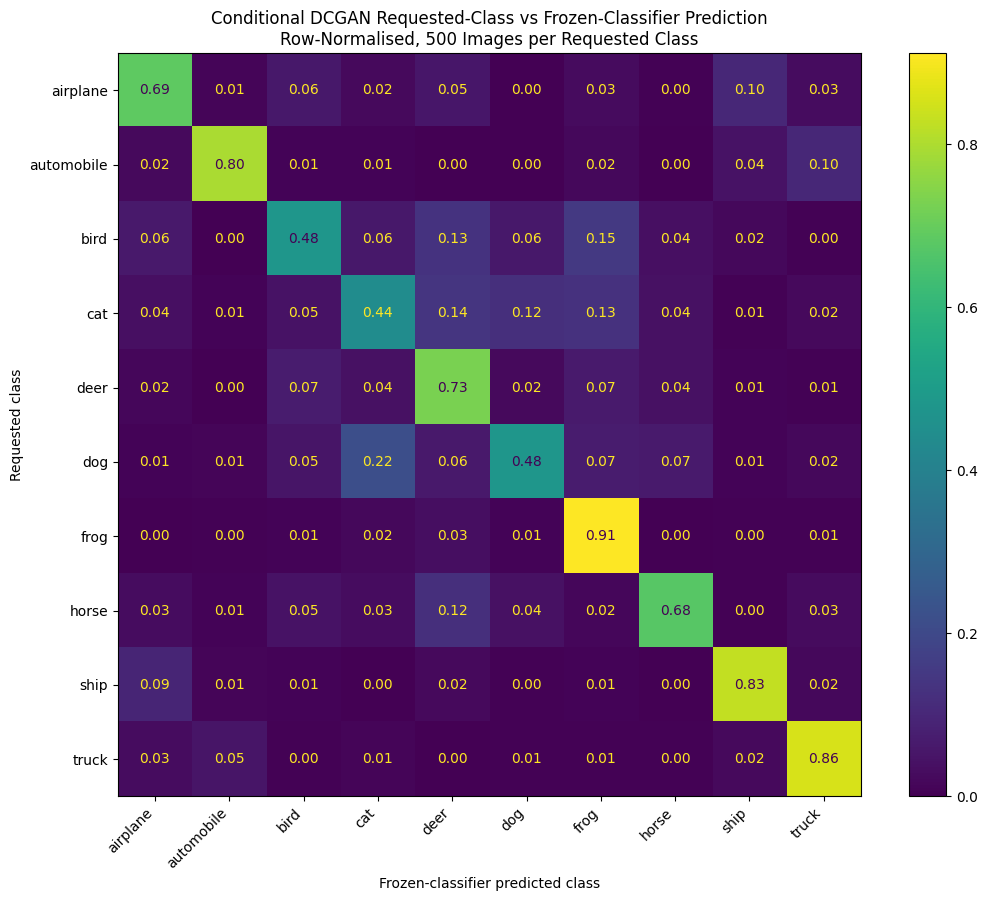

Classifier overall agreement: 0.6890
Mean requested-class probability: 0.6302
Normalised mutual information: 0.5140
Requested class is row maximum: 10 / 10
Represented predicted classes: 10
Confusion counts saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_requested_vs_predicted_counts.csv
Confusion proportions saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_requested_vs_predicted_proportions.csv
Confusion figure saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_requested_vs_predicted_confusion.png
Generated pool remains in memory for class-wise diversity and repetition analysis.
Classifier results remain supporting evidence, not generated-image ground truth.
Protected test set remains unused.


In [81]:
conditional_confusion_counts_df = pd.DataFrame(
    conditional_requested_vs_predicted_counts,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

conditional_confusion_proportions_df = pd.DataFrame(
    conditional_requested_vs_predicted_proportions,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)


CONDITIONAL_CONFUSION_COUNTS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "requested_vs_predicted_counts.csv"
    )
)

CONDITIONAL_CONFUSION_PROPORTIONS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "requested_vs_predicted_proportions.csv"
    )
)

CONDITIONAL_CONFUSION_FIGURE_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "requested_vs_predicted_confusion.png"
    )
)


conditional_confusion_counts_df.to_csv(
    CONDITIONAL_CONFUSION_COUNTS_PATH,
    index=True,
)

conditional_confusion_proportions_df.to_csv(
    CONDITIONAL_CONFUSION_PROPORTIONS_PATH,
    index=True,
)


figure, axis = plt.subplots(
    figsize=(11, 9)
)


confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=(
        conditional_requested_vs_predicted_proportions
    ),
    display_labels=CLASS_NAMES,
)


confusion_display.plot(
    ax=axis,
    values_format=".2f",
    colorbar=True,
)


axis.set_title(
    (
        "Conditional DCGAN Requested-Class "
        "vs Frozen-Classifier Prediction\n"
        "Row-Normalised, 500 Images per Requested Class"
    )
)

axis.set_xlabel(
    "Frozen-classifier predicted class"
)

axis.set_ylabel(
    "Requested class"
)


plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    CONDITIONAL_CONFUSION_FIGURE_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Classifier overall agreement:",
    f"{CONDITIONAL_CLASSIFIER_OVERALL_AGREEMENT:.4f}",
)

print(
    "Mean requested-class probability:",
    (
        f"{CONDITIONAL_CLASSIFIER_MEAN_REQUESTED_PROBABILITY:.4f}"
    ),
)

print(
    "Normalised mutual information:",
    (
        f"{CONDITIONAL_CLASSIFIER_NORMALISED_MUTUAL_INFORMATION:.4f}"
    ),
)

print(
    "Requested class is row maximum:",
    (
        f"{CONDITIONAL_REQUESTED_CLASSES_TOP_PREDICTION_COUNT}"
        f" / {NUM_CLASSES}"
    ),
)

print(
    "Represented predicted classes:",
    int(
        np.count_nonzero(
            conditional_predicted_counts
        )
    ),
)

print(
    "Confusion counts saved:",
    CONDITIONAL_CONFUSION_COUNTS_PATH,
)

print(
    "Confusion proportions saved:",
    CONDITIONAL_CONFUSION_PROPORTIONS_PATH,
)

print(
    "Confusion figure saved:",
    CONDITIONAL_CONFUSION_FIGURE_PATH,
)

print(
    "Generated pool remains in memory for "
    "class-wise diversity and repetition analysis."
)

print(
    "Classifier results remain supporting evidence, "
    "not generated-image ground truth."
)

print("Protected test set remains unused.")

#### Frozen-Classifier Adherence Interpretation

The frozen classifier agreed with the requested label for `68.9%` of the balanced 5,000-image pool.

The requested class was the most common classifier prediction for all ten requested rows, and all ten predicted classes were represented. The normalised mutual information of `0.5140` provides supporting evidence that the generator does not globally ignore its conditioning labels.

The aggregate predicted distribution remained well balanced:

- dominant predicted-class share: `0.1404`;
- normalised predicted-class entropy: `0.9910`;
- JS divergence from held-out-real classifier predictions: `0.0039`.

The strongest classifier-supported agreement appeared for frogs, trucks, ships and automobiles. Birds, cats and dogs produced the weakest agreement and showed confusion among visually related animal classes.

The frog result requires caution. The classifier assigned `91.2%` of frog-requested images to the frog class, while the strict manual review judged only one of ten frog images Correct. This disagreement suggests that the classifier may be responding to frog-associated colour, texture or low-level patterns that are not sufficiently recognisable to a human reviewer.

The classifier results therefore corroborate that conditioning affects generation, but they do not replace manual judgement of semantic recognisability.

### 13.12 Low-Level Image Descriptor Comparison

The existing 5,000-image conditional evaluation pool is compared with the complete real CIFAR-10 training reference using the seven descriptors established in Notebook 1:

- brightness;
- contrast;
- mean red;
- mean green;
- mean blue;
- saturation;
- edge strength.

The comparison reports mean alignment and variation alignment relative to real CIFAR-10.

The previously saved descriptor comparison for the selected augmented unconditional seed-42 model is reused rather than recomputed. This allows the conditional and unconditional finalists to be compared using the same descriptor definitions and evaluation depth.

These descriptors provide supporting evidence about low-level image statistics. They do not directly measure semantic recognisability or requested-class adherence.

In [82]:
required_conditional_descriptor_objects = [
    "conditional_automated_images",
    "CONDITIONAL_SEED42_RUN_ID",
    "DESCRIPTOR_COLUMNS",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "real_descriptor_df",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_descriptor_objects = [
    name
    for name in required_conditional_descriptor_objects
    if name not in globals()
]

assert not missing_conditional_descriptor_objects, (
    "Incomplete conditional descriptor setup:\n"
    + "\n".join(
        missing_conditional_descriptor_objects
    )
)


assert conditional_automated_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert conditional_automated_images.dtype == np.uint8


conditional_descriptor_df = (
    calculate_image_descriptors(
        images_uint8=conditional_automated_images,
        batch_size=1_000,
    )
)


assert conditional_descriptor_df.shape == (
    5_000,
    7,
)

assert (
    conditional_descriptor_df.columns.tolist()
    == DESCRIPTOR_COLUMNS
)

assert np.isfinite(
    conditional_descriptor_df.to_numpy(
        dtype=np.float64
    )
).all()


conditional_descriptor_comparison_df = (
    build_descriptor_comparison(
        real_descriptors=real_descriptor_df,
        generated_descriptors=(
            conditional_descriptor_df
        ),
    )
)


conditional_descriptor_comparison_df = (
    conditional_descriptor_comparison_df
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)


CONDITIONAL_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "descriptor_comparison.csv"
    )
)


conditional_descriptor_comparison_df.to_csv(
    CONDITIONAL_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)


display(
    conditional_descriptor_comparison_df.round(4)
)


print(
    "Conditional descriptor comparison saved:",
    CONDITIONAL_DESCRIPTOR_COMPARISON_PATH,
)

print(
    "The existing 5,000-image conditional pool "
    "was reused."
)

print("Protected test set remains unused.")

,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio
0,Brightness,0.4816,0.4621,0.0194,0.1233,0.1280,1.0375
1,Contrast,0.1970,0.1961,0.0009,0.0603,0.0622,1.0324
2,Mean Red,0.4914,0.4690,0.0224,0.1284,0.1314,1.0237
3,Mean Green,0.4822,0.4627,0.0195,0.1258,0.1308,1.0395
4,Mean Blue,0.4465,0.4357,0.0108,0.1533,0.1539,1.0038
5,Saturation,0.2738,0.2665,0.0073,0.1415,0.1318,0.9315
6,Edge Strength,0.5183,0.5108,0.0075,0.1547,0.1574,1.0173


Conditional descriptor comparison saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_descriptor_comparison.csv
The existing 5,000-image conditional pool was reused.
Protected test set remains unused.


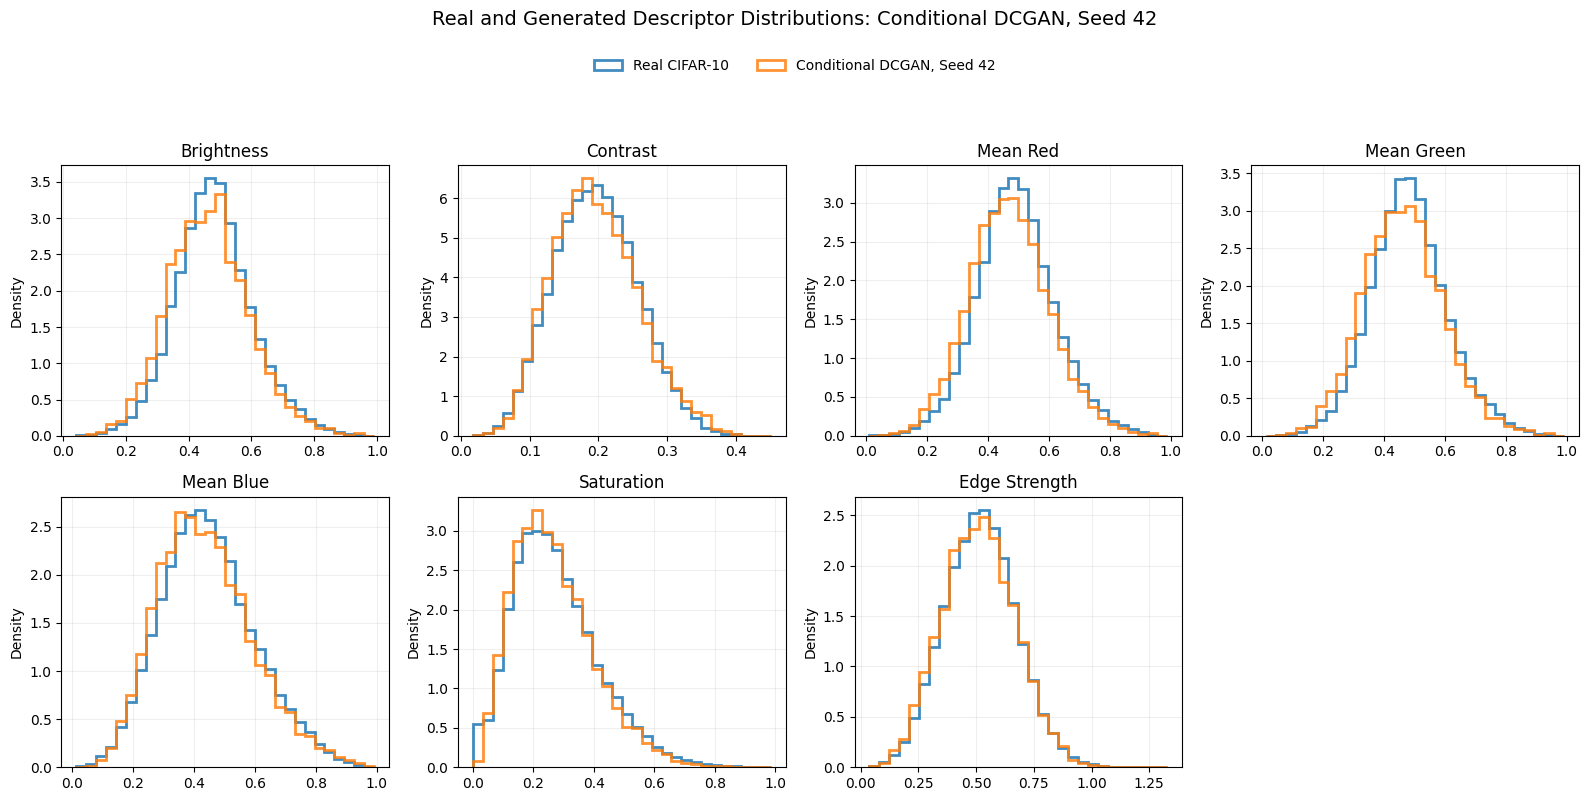

Conditional descriptor plot saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_descriptor_distributions.png
Protected test set remains unused.


In [83]:
required_conditional_descriptor_plot_objects = [
    "conditional_descriptor_df",
    "real_descriptor_df",
    "plot_descriptor_distributions",
    "CONDITIONAL_SEED42_RUN_ID",
    "GRIDS_DIR",
]

missing_conditional_descriptor_plot_objects = [
    name
    for name in required_conditional_descriptor_plot_objects
    if name not in globals()
]

assert not missing_conditional_descriptor_plot_objects, (
    "Incomplete conditional descriptor-plot setup:\n"
    + "\n".join(
        missing_conditional_descriptor_plot_objects
    )
)


CONDITIONAL_DESCRIPTOR_PLOT_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "descriptor_distributions.png"
    )
)


plot_descriptor_distributions(
    real_descriptors=real_descriptor_df,
    generated_descriptors=(
        conditional_descriptor_df
    ),
    model_label="Conditional DCGAN, Seed 42",
    output_path=(
        CONDITIONAL_DESCRIPTOR_PLOT_PATH
    ),
    bin_count=30,
)


print(
    "Conditional descriptor plot saved:",
    CONDITIONAL_DESCRIPTOR_PLOT_PATH,
)

print("Protected test set remains unused.")

In [84]:
required_conditional_descriptor_closeness_objects = [
    "conditional_descriptor_comparison_df",
    "DESCRIPTOR_COLUMNS",
    "HISTORIES_DIR",
    "CONDITIONAL_SEED42_RUN_ID",
    "pd",
    "np",
]

missing_conditional_descriptor_closeness_objects = [
    name
    for name in required_conditional_descriptor_closeness_objects
    if name not in globals()
]

assert not missing_conditional_descriptor_closeness_objects, (
    "Incomplete conditional descriptor-closeness setup:\n"
    + "\n".join(
        missing_conditional_descriptor_closeness_objects
    )
)


SELECTED_UNCONDITIONAL_DESCRIPTOR_COMPARISON_PATH = (
    HISTORIES_DIR
    / (
        "final_unconditional_seed42_"
        "descriptor_comparison.csv"
    )
)


assert (
    SELECTED_UNCONDITIONAL_DESCRIPTOR_COMPARISON_PATH
    .is_file()
), (
    "Missing selected-unconditional descriptor comparison:\n"
    f"{SELECTED_UNCONDITIONAL_DESCRIPTOR_COMPARISON_PATH}"
)


selected_unconditional_descriptor_comparison_df = (
    pd.read_csv(
        SELECTED_UNCONDITIONAL_DESCRIPTOR_COMPARISON_PATH
    )
    .set_index("Descriptor")
    .loc[DESCRIPTOR_COLUMNS]
    .reset_index()
)


assert len(
    selected_unconditional_descriptor_comparison_df
) == 7

assert len(
    conditional_descriptor_comparison_df
) == 7


unconditional_mean_errors = (
    selected_unconditional_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)

conditional_mean_errors = (
    conditional_descriptor_comparison_df[
        "Absolute Mean Difference"
    ].to_numpy(dtype=np.float64)
)


unconditional_variation_errors = np.abs(
    selected_unconditional_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)

conditional_variation_errors = np.abs(
    conditional_descriptor_comparison_df[
        "Generated-to-Real SD Ratio"
    ].to_numpy(dtype=np.float64)
    - 1.0
)


mean_ties = np.isclose(
    unconditional_mean_errors,
    conditional_mean_errors,
    atol=1e-12,
    rtol=0.0,
)

variation_ties = np.isclose(
    unconditional_variation_errors,
    conditional_variation_errors,
    atol=1e-12,
    rtol=0.0,
)


mean_closer_labels = np.where(
    mean_ties,
    "Tie",
    np.where(
        conditional_mean_errors
        < unconditional_mean_errors,
        "Conditional",
        "Unconditional",
    ),
)

variation_closer_labels = np.where(
    variation_ties,
    "Tie",
    np.where(
        conditional_variation_errors
        < unconditional_variation_errors,
        "Conditional",
        "Unconditional",
    ),
)


conditional_descriptor_closeness_df = pd.DataFrame(
    {
        "Descriptor": DESCRIPTOR_COLUMNS,
        "Unconditional mean error": (
            unconditional_mean_errors
        ),
        "Conditional mean error": (
            conditional_mean_errors
        ),
        "Unconditional variation error": (
            unconditional_variation_errors
        ),
        "Conditional variation error": (
            conditional_variation_errors
        ),
        "Mean closer to real": (
            mean_closer_labels
        ),
        "Variation closer to real": (
            variation_closer_labels
        ),
    }
)


CONDITIONAL_DESCRIPTOR_CLOSENESS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "descriptor_closeness_vs_unconditional.csv"
    )
)


conditional_descriptor_closeness_df.to_csv(
    CONDITIONAL_DESCRIPTOR_CLOSENESS_PATH,
    index=False,
)


display(
    conditional_descriptor_closeness_df.round(4)
)


print("Mean closeness")

print(
    conditional_descriptor_closeness_df[
        "Mean closer to real"
    ].value_counts()
)


print("Variation closeness")

print(
    conditional_descriptor_closeness_df[
        "Variation closer to real"
    ].value_counts()
)


print(
    "Descriptor closeness comparison saved:",
    CONDITIONAL_DESCRIPTOR_CLOSENESS_PATH,
)

print(
    "No final unconditional-versus-conditional "
    "decision has been made."
)

print("Protected test set remains unused.")

,Descriptor,Unconditional mean error,Conditional mean error,Unconditional variation error,Conditional variation error,Mean closer to real,Variation closer to real
0,Brightness,0.0010,0.0194,0.0097,0.0375,Unconditional,Unconditional
1,Contrast,0.0002,0.0009,0.0158,0.0324,Unconditional,Unconditional
2,Mean Red,0.0076,0.0224,0.0113,0.0237,Unconditional,Unconditional
3,Mean Green,0.0002,0.0195,0.0069,0.0395,Unconditional,Unconditional
4,Mean Blue,0.0104,0.0108,0.0393,0.0038,Unconditional,Conditional
5,Saturation,0.0009,0.0073,0.0099,0.0685,Unconditional,Unconditional
6,Edge Strength,0.0048,0.0075,0.0353,0.0173,Unconditional,Conditional


Mean closeness
Mean closer to real
Unconditional    7
Name: count, dtype: int64
Variation closeness
Variation closer to real
Unconditional    5
Conditional      2
Name: count, dtype: int64
Descriptor closeness comparison saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_descriptor_closeness_vs_unconditional.csv
No final unconditional-versus-conditional decision has been made.
Protected test set remains unused.


#### Per-Class Conditional Descriptor Analysis

The aggregate descriptor comparison shows that the conditional model is less closely aligned with real CIFAR-10 than the selected unconditional model.

To determine whether this shift is distributed across all classes or concentrated in specific requested classes, each conditional class is now compared with the corresponding true CIFAR-10 training class.

For every class and descriptor, the analysis reports:

- real and generated means;
- signed and absolute mean differences;
- the mean shift measured in units of the real class standard deviation;
- real and generated standard deviations;
- generated-to-real standard-deviation ratio;
- absolute variation error from the ideal ratio of `1.0`.

The standardised mean-shift heatmap makes descriptor differences comparable across classes. Negative values indicate that the conditional outputs have a lower descriptor mean than the corresponding real class.

This analysis remains descriptive supporting evidence. It does not replace FID, manual recognisability or requested-class adherence.

In [86]:
required_conditional_class_descriptor_objects = [
    "conditional_descriptor_df",
    "conditional_automated_requested_labels",
    "real_descriptor_df",
    "y_train",
    "DESCRIPTOR_COLUMNS",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "CONDITIONAL_SEED42_RUN_ID",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_class_descriptor_objects = [
    name
    for name in required_conditional_class_descriptor_objects
    if name not in globals()
]

assert not missing_conditional_class_descriptor_objects, (
    "Incomplete per-class descriptor setup:\n"
    + "\n".join(
        missing_conditional_class_descriptor_objects
    )
)


conditional_descriptor_labels = np.asarray(
    conditional_automated_requested_labels,
    dtype=np.int64,
).reshape(-1)

real_training_labels = np.asarray(
    y_train,
    dtype=np.int64,
).reshape(-1)


assert conditional_descriptor_df.shape == (
    5_000,
    len(DESCRIPTOR_COLUMNS),
)

assert real_descriptor_df.shape == (
    50_000,
    len(DESCRIPTOR_COLUMNS),
)

assert conditional_descriptor_labels.shape == (
    5_000,
)

assert real_training_labels.shape == (
    50_000,
)

assert conditional_descriptor_df.columns.tolist() == (
    DESCRIPTOR_COLUMNS
)

assert real_descriptor_df.columns.tolist() == (
    DESCRIPTOR_COLUMNS
)


conditional_class_descriptor_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    real_class_indices = np.flatnonzero(
        real_training_labels == class_index
    )

    generated_class_indices = np.flatnonzero(
        conditional_descriptor_labels == class_index
    )


    assert len(real_class_indices) == 5_000

    assert len(generated_class_indices) == 500


    real_class_descriptor_df = (
        real_descriptor_df.iloc[
            real_class_indices
        ]
    )

    generated_class_descriptor_df = (
        conditional_descriptor_df.iloc[
            generated_class_indices
        ]
    )


    real_class_means = (
        real_class_descriptor_df[
            DESCRIPTOR_COLUMNS
        ]
        .mean()
        .to_numpy(dtype=np.float64)
    )

    generated_class_means = (
        generated_class_descriptor_df[
            DESCRIPTOR_COLUMNS
        ]
        .mean()
        .to_numpy(dtype=np.float64)
    )

    real_class_standard_deviations = (
        real_class_descriptor_df[
            DESCRIPTOR_COLUMNS
        ]
        .std(ddof=1)
        .to_numpy(dtype=np.float64)
    )

    generated_class_standard_deviations = (
        generated_class_descriptor_df[
            DESCRIPTOR_COLUMNS
        ]
        .std(ddof=1)
        .to_numpy(dtype=np.float64)
    )


    assert np.isfinite(
        real_class_means
    ).all()

    assert np.isfinite(
        generated_class_means
    ).all()

    assert np.isfinite(
        real_class_standard_deviations
    ).all()

    assert np.isfinite(
        generated_class_standard_deviations
    ).all()

    assert (
        real_class_standard_deviations
        > 0.0
    ).all()


    signed_mean_differences = (
        generated_class_means
        - real_class_means
    )

    absolute_mean_differences = np.abs(
        signed_mean_differences
    )

    standardised_mean_shifts = (
        signed_mean_differences
        / real_class_standard_deviations
    )

    generated_to_real_sd_ratios = (
        generated_class_standard_deviations
        / real_class_standard_deviations
    )

    absolute_variation_errors = np.abs(
        generated_to_real_sd_ratios
        - 1.0
    )


    for descriptor_index, descriptor_name in enumerate(
        DESCRIPTOR_COLUMNS
    ):
        conditional_class_descriptor_rows.append(
            {
                "Class index": class_index,
                "Requested class": class_name,
                "Descriptor": descriptor_name,
                "Real sample count": int(
                    len(real_class_indices)
                ),
                "Generated sample count": int(
                    len(generated_class_indices)
                ),
                "Real mean": float(
                    real_class_means[
                        descriptor_index
                    ]
                ),
                "Generated mean": float(
                    generated_class_means[
                        descriptor_index
                    ]
                ),
                "Signed mean difference": float(
                    signed_mean_differences[
                        descriptor_index
                    ]
                ),
                "Absolute mean difference": float(
                    absolute_mean_differences[
                        descriptor_index
                    ]
                ),
                "Standardised mean shift": float(
                    standardised_mean_shifts[
                        descriptor_index
                    ]
                ),
                "Real standard deviation": float(
                    real_class_standard_deviations[
                        descriptor_index
                    ]
                ),
                "Generated standard deviation": float(
                    generated_class_standard_deviations[
                        descriptor_index
                    ]
                ),
                "Generated-to-real SD ratio": float(
                    generated_to_real_sd_ratios[
                        descriptor_index
                    ]
                ),
                "Absolute variation error": float(
                    absolute_variation_errors[
                        descriptor_index
                    ]
                ),
            }
        )


conditional_class_descriptor_long_df = pd.DataFrame(
    conditional_class_descriptor_rows
)


assert len(
    conditional_class_descriptor_long_df
) == (
    NUM_CLASSES
    * len(DESCRIPTOR_COLUMNS)
)

assert np.isfinite(
    conditional_class_descriptor_long_df[
        [
            "Real mean",
            "Generated mean",
            "Signed mean difference",
            "Absolute mean difference",
            "Standardised mean shift",
            "Real standard deviation",
            "Generated standard deviation",
            "Generated-to-real SD ratio",
            "Absolute variation error",
        ]
    ].to_numpy(dtype=np.float64)
).all()


conditional_class_descriptor_summary_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    class_result_df = (
        conditional_class_descriptor_long_df.loc[
            conditional_class_descriptor_long_df[
                "Class index"
            ]
            == class_index
        ]
        .reset_index(drop=True)
    )


    assert len(class_result_df) == len(
        DESCRIPTOR_COLUMNS
    )


    largest_mean_shift_row = (
        class_result_df.loc[
            class_result_df[
                "Standardised mean shift"
            ]
            .abs()
            .idxmax()
        ]
    )

    largest_variation_error_row = (
        class_result_df.loc[
            class_result_df[
                "Absolute variation error"
            ]
            .idxmax()
        ]
    )


    conditional_class_descriptor_summary_rows.append(
        {
            "Class index": class_index,
            "Requested class": class_name,
            "Mean absolute descriptor difference": float(
                class_result_df[
                    "Absolute mean difference"
                ].mean()
            ),
            "Mean absolute standardised shift": float(
                class_result_df[
                    "Standardised mean shift"
                ]
                .abs()
                .mean()
            ),
            "Descriptors below real mean": int(
                (
                    class_result_df[
                        "Signed mean difference"
                    ]
                    < 0.0
                ).sum()
            ),
            "Descriptors above real mean": int(
                (
                    class_result_df[
                        "Signed mean difference"
                    ]
                    > 0.0
                ).sum()
            ),
            "Largest standardised shift descriptor": (
                largest_mean_shift_row[
                    "Descriptor"
                ]
            ),
            "Largest standardised shift": float(
                largest_mean_shift_row[
                    "Standardised mean shift"
                ]
            ),
            "Mean absolute variation error": float(
                class_result_df[
                    "Absolute variation error"
                ].mean()
            ),
            "Largest variation error descriptor": (
                largest_variation_error_row[
                    "Descriptor"
                ]
            ),
            "Largest variation error": float(
                largest_variation_error_row[
                    "Absolute variation error"
                ]
            ),
        }
    )


conditional_class_descriptor_summary_df = pd.DataFrame(
    conditional_class_descriptor_summary_rows
)


CONDITIONAL_CLASS_DESCRIPTOR_LONG_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classwise_descriptor_comparison.csv"
    )
)

CONDITIONAL_CLASS_DESCRIPTOR_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classwise_descriptor_summary.csv"
    )
)


conditional_class_descriptor_long_df.to_csv(
    CONDITIONAL_CLASS_DESCRIPTOR_LONG_PATH,
    index=False,
)

conditional_class_descriptor_summary_df.to_csv(
    CONDITIONAL_CLASS_DESCRIPTOR_SUMMARY_PATH,
    index=False,
)


display(
    conditional_class_descriptor_summary_df.round(4)
)


print(
    "Largest mean-shift classes:"
)

display(
    conditional_class_descriptor_summary_df.sort_values(
        "Mean absolute standardised shift",
        ascending=False,
    )
    .head(5)
    .round(4)
)


print(
    "Per-class descriptor comparison saved:",
    CONDITIONAL_CLASS_DESCRIPTOR_LONG_PATH,
)

print(
    "Per-class descriptor summary saved:",
    CONDITIONAL_CLASS_DESCRIPTOR_SUMMARY_PATH,
)

print("Protected test set remains unused.")

,Class index,Requested class,Mean absolute descriptor difference,Mean absolute standardised shift,Descriptors below real mean,Descriptors above real mean,Largest standardised shift descriptor,Largest standardised shift,Mean absolute variation error,Largest variation error descriptor,Largest variation error
0,0,airplane,0.0184,0.1380,6,1,Edge Strength,-0.2186,0.0468,Mean Red,0.0792
1,1,automobile,0.0327,0.2603,7,0,Mean Red,-0.4292,0.0648,Contrast,0.2382
2,2,bird,0.0083,0.0649,7,0,Edge Strength,-0.1339,0.0401,Saturation,0.1006
3,3,cat,0.0174,0.1322,5,2,Mean Red,-0.2523,0.0424,Saturation,0.0870
4,4,deer,0.0092,0.0722,1,6,Saturation,-0.2245,0.0587,Saturation,0.1176
5,5,dog,0.0138,0.1185,4,3,Edge Strength,0.1675,0.0961,Brightness,0.1417
6,6,frog,0.0144,0.1150,7,0,Mean Green,-0.1758,0.0966,Saturation,0.1684
7,7,horse,0.0076,0.0721,7,0,Saturation,-0.1332,0.0591,Saturation,0.0942
8,8,ship,0.0061,0.0552,6,1,Mean Red,-0.0989,0.0614,Mean Blue,0.1094
9,9,truck,0.0286,0.2789,5,2,Mean Red,-0.4663,0.0557,Contrast,0.1672


Largest mean-shift classes:


,Class index,Requested class,Mean absolute descriptor difference,Mean absolute standardised shift,Descriptors below real mean,Descriptors above real mean,Largest standardised shift descriptor,Largest standardised shift,Mean absolute variation error,Largest variation error descriptor,Largest variation error
9,9,truck,0.0286,0.2789,5,2,Mean Red,-0.4663,0.0557,Contrast,0.1672
1,1,automobile,0.0327,0.2603,7,0,Mean Red,-0.4292,0.0648,Contrast,0.2382
0,0,airplane,0.0184,0.1380,6,1,Edge Strength,-0.2186,0.0468,Mean Red,0.0792
3,3,cat,0.0174,0.1322,5,2,Mean Red,-0.2523,0.0424,Saturation,0.0870
5,5,dog,0.0138,0.1185,4,3,Edge Strength,0.1675,0.0961,Brightness,0.1417


Per-class descriptor comparison saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_classwise_descriptor_comparison.csv
Per-class descriptor summary saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_classwise_descriptor_summary.csv
Protected test set remains unused.


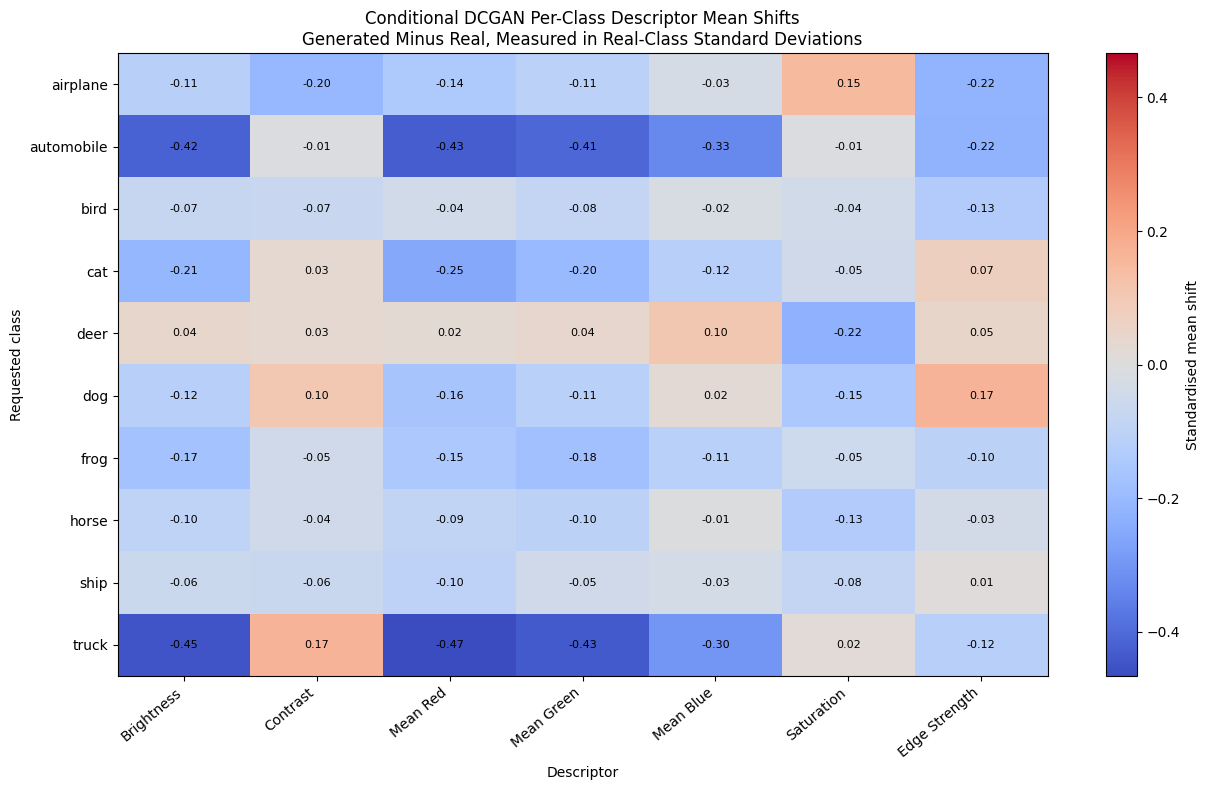

Per-class descriptor heatmap saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_classwise_descriptor_standardised_shifts.png
Negative values indicate lower generated descriptor means than the real class.
Descriptor interpretation remains pending until the class-wise pattern is reviewed.
Protected test set remains unused.


In [87]:
required_conditional_class_descriptor_plot_objects = [
    "conditional_class_descriptor_long_df",
    "DESCRIPTOR_COLUMNS",
    "CLASS_NAMES",
    "CONDITIONAL_SEED42_RUN_ID",
    "GRIDS_DIR",
    "np",
    "plt",
]

missing_conditional_class_descriptor_plot_objects = [
    name
    for name in required_conditional_class_descriptor_plot_objects
    if name not in globals()
]

assert not missing_conditional_class_descriptor_plot_objects, (
    "Incomplete per-class descriptor-plot setup:\n"
    + "\n".join(
        missing_conditional_class_descriptor_plot_objects
    )
)


conditional_class_descriptor_shift_matrix = (
    conditional_class_descriptor_long_df
    .pivot(
        index="Requested class",
        columns="Descriptor",
        values="Standardised mean shift",
    )
    .loc[
        list(CLASS_NAMES),
        DESCRIPTOR_COLUMNS,
    ]
)


assert conditional_class_descriptor_shift_matrix.shape == (
    NUM_CLASSES,
    len(DESCRIPTOR_COLUMNS),
)

assert np.isfinite(
    conditional_class_descriptor_shift_matrix
    .to_numpy(dtype=np.float64)
).all()


conditional_class_descriptor_heatmap_values = (
    conditional_class_descriptor_shift_matrix
    .to_numpy(dtype=np.float64)
)

conditional_class_descriptor_heatmap_limit = float(
    max(
        0.25,
        np.max(
            np.abs(
                conditional_class_descriptor_heatmap_values
            )
        ),
    )
)


CONDITIONAL_CLASS_DESCRIPTOR_HEATMAP_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classwise_descriptor_standardised_shifts.png"
    )
)


figure, axis = plt.subplots(
    figsize=(13, 8)
)


heatmap = axis.imshow(
    conditional_class_descriptor_heatmap_values,
    aspect="auto",
    cmap="coolwarm",
    vmin=(
        -conditional_class_descriptor_heatmap_limit
    ),
    vmax=(
        conditional_class_descriptor_heatmap_limit
    ),
)


axis.set_xticks(
    np.arange(
        len(DESCRIPTOR_COLUMNS)
    )
)

axis.set_xticklabels(
    DESCRIPTOR_COLUMNS,
    rotation=40,
    ha="right",
)

axis.set_yticks(
    np.arange(
        NUM_CLASSES
    )
)

axis.set_yticklabels(
    CLASS_NAMES
)


for class_index in range(
    NUM_CLASSES
):
    for descriptor_index in range(
        len(DESCRIPTOR_COLUMNS)
    ):
        shift_value = (
            conditional_class_descriptor_heatmap_values[
                class_index,
                descriptor_index,
            ]
        )

        axis.text(
            descriptor_index,
            class_index,
            f"{shift_value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )


axis.set_title(
    (
        "Conditional DCGAN Per-Class Descriptor "
        "Mean Shifts\n"
        "Generated Minus Real, Measured in "
        "Real-Class Standard Deviations"
    )
)

axis.set_xlabel("Descriptor")
axis.set_ylabel("Requested class")


colour_bar = figure.colorbar(
    heatmap,
    ax=axis,
)

colour_bar.set_label(
    "Standardised mean shift"
)


figure.tight_layout()

figure.savefig(
    CONDITIONAL_CLASS_DESCRIPTOR_HEATMAP_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Per-class descriptor heatmap saved:",
    CONDITIONAL_CLASS_DESCRIPTOR_HEATMAP_PATH,
)

print(
    "Negative values indicate lower generated "
    "descriptor means than the real class."
)

print(
    "Descriptor interpretation remains pending "
    "until the class-wise pattern is reviewed."
)

print("Protected test set remains unused.")

#### Descriptor Interpretation

The aggregate descriptor evidence favours the selected augmented unconditional model. It is closer to real CIFAR-10 for all seven descriptor means and for five of seven descriptor variations.

The class-wise analysis shows that this difference is not distributed uniformly across the ten requested classes.

The largest average standardised descriptor shifts occurred for:

- truck: `0.2789`;
- automobile: `0.2603`;
- airplane: `0.1380`;
- cat: `0.1322`;
- dog: `0.1185`.

Truck and automobile outputs contributed most strongly to the aggregate shift. Both classes were systematically darker and had lower red, green and blue means than their corresponding real CIFAR-10 classes. The largest individual difference was the truck Mean Red shift of approximately `−0.47` real-class standard deviations.

The initially plausible explanation that green and brown animal classes such as frogs or deer were driving the aggregate difference was not supported. Deer remained close to its real-class descriptor means apart from lower saturation, while the frog shifts were moderate rather than dominant. Bird and ship showed the smallest overall mean discrepancies.

Most generated descriptor means remained below the corresponding real-class means, indicating a general but class-dependent darkening and colour attenuation tendency. Variation mismatches were most notable for dogs and frogs, although these remained supporting rather than decisive evidence.

The shifts are measurable but not severe. Every class had a mean absolute standardised shift below `0.30`, and the largest individual descriptor shift remained below `0.50` real-class standard deviations.

The conditional model therefore preserves broad CIFAR-10 low-level appearance but reproduces real colour and brightness statistics less faithfully than the selected unconditional model. This is recorded as a genuine cost of adding requested-class control, not as an automatic model-selection veto.

### 13.13 Diversity and Repetition

The existing balanced 5,000-image conditional evaluation pool is reused to evaluate feature-space diversity and repetition.

The global analysis uses ten reproducible repeats. Each repeat compares random subsets of:

- 1,000 real CIFAR-10 training images;
- 1,000 conditional generated images.

For every repeat, the analysis reports pairwise feature distance, nearest-neighbour distance, generated-to-real diversity ratio and the near-duplicate rate relative to the real subset's first-percentile nearest-neighbour threshold.

Exact pixel duplicates are checked separately across all 5,000 generated images.

Because global conditional diversity includes separation between different requested classes, a second analysis evaluates within-class diversity independently for each requested class.

These checks measure generated-to-generated repetition and collapse. They are not the formal generated-to-training memorisation audit reserved for Notebook 4.

In [88]:
required_conditional_diversity_objects = [
    "compact_cosine_diversity_summary",
    "extract_inception_features",
    "fid_feature_extractor",
    "real_fid_features",
    "conditional_automated_images",
    "conditional_automated_requested_labels",
    "CONDITIONAL_SEED42_RUN_ID",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "y_train",
    "HISTORIES_DIR",
    "np",
    "pd",
]

missing_conditional_diversity_objects = [
    name
    for name in required_conditional_diversity_objects
    if name not in globals()
]

assert not missing_conditional_diversity_objects, (
    "Incomplete conditional diversity setup:\n"
    + "\n".join(
        missing_conditional_diversity_objects
    )
)


assert conditional_automated_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert conditional_automated_images.dtype == np.uint8

conditional_automated_requested_labels = np.asarray(
    conditional_automated_requested_labels,
    dtype=np.int64,
).reshape(-1)

assert conditional_automated_requested_labels.shape == (
    5_000,
)

assert real_fid_features.shape == (
    50_000,
    2_048,
)


CONDITIONAL_DIVERSITY_SUBSET_SIZE = 1_000
CONDITIONAL_DIVERSITY_REPEAT_COUNT = 10

CONDITIONAL_REAL_DIVERSITY_SEED = 1301
CONDITIONAL_GENERATED_DIVERSITY_SEED = 1302

CONDITIONAL_NEAR_DUPLICATE_PERCENTILE = 1.0


if "conditional_automated_features" not in globals():
    conditional_automated_features = (
        extract_inception_features(
            images_uint8=(
                conditional_automated_images
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=64,
        )
    )


assert conditional_automated_features.shape == (
    5_000,
    2_048,
)

assert np.isfinite(
    conditional_automated_features
).all()


print(
    "Conditional diversity feature pool ready."
)

print(
    "Generated feature shape:",
    conditional_automated_features.shape,
)

print(
    "Real feature shape:",
    real_fid_features.shape,
)

print(
    "The existing 5,000-image pool was reused."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Conditional diversity feature pool ready.
Generated feature shape: (5000, 2048)
Real feature shape: (50000, 2048)
The existing 5,000-image pool was reused.
Protected test set remains unused.


In [89]:
conditional_real_diversity_rng = (
    np.random.default_rng(
        CONDITIONAL_REAL_DIVERSITY_SEED
    )
)

conditional_generated_diversity_rng = (
    np.random.default_rng(
        CONDITIONAL_GENERATED_DIVERSITY_SEED
    )
)


conditional_diversity_repeat_rows = []

CONDITIONAL_REPRESENTATIVE_REAL_NEAREST_DISTANCES = None
CONDITIONAL_REPRESENTATIVE_GENERATED_NEAREST_DISTANCES = None
CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_THRESHOLD = None
CONDITIONAL_REPRESENTATIVE_GENERATED_INDICES = None


for repeat_index in range(
    1,
    CONDITIONAL_DIVERSITY_REPEAT_COUNT + 1,
):
    real_indices = (
        conditional_real_diversity_rng.choice(
            len(real_fid_features),
            size=CONDITIONAL_DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        conditional_generated_diversity_rng.choice(
            len(conditional_automated_features),
            size=CONDITIONAL_DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )


    real_summary = (
        compact_cosine_diversity_summary(
            real_fid_features[
                real_indices
            ]
        )
    )

    generated_summary = (
        compact_cosine_diversity_summary(
            conditional_automated_features[
                generated_indices
            ]
        )
    )


    near_duplicate_threshold = float(
        np.percentile(
            real_summary[
                "nearest_distances"
            ],
            CONDITIONAL_NEAR_DUPLICATE_PERCENTILE,
        )
    )

    near_duplicate_rate = float(
        np.mean(
            generated_summary[
                "nearest_distances"
            ]
            < near_duplicate_threshold
        )
        * 100.0
    )

    diversity_ratio = float(
        generated_summary[
            "mean_pairwise_distance"
        ]
        / real_summary[
            "mean_pairwise_distance"
        ]
    )


    conditional_diversity_repeat_rows.append(
        {
            "Repeat": repeat_index,
            "Feature sample count": (
                CONDITIONAL_DIVERSITY_SUBSET_SIZE
            ),
            "Real mean pairwise distance": (
                real_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "Generated mean pairwise distance": (
                generated_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "Generated median pairwise distance": (
                generated_summary[
                    "median_pairwise_distance"
                ]
            ),
            "Generated median nearest distance": (
                generated_summary[
                    "median_nearest_distance"
                ]
            ),
            "Generated minimum nearest distance": (
                generated_summary[
                    "minimum_nearest_distance"
                ]
            ),
            "Near-duplicate threshold": (
                near_duplicate_threshold
            ),
            "Near-duplicate rate (%)": (
                near_duplicate_rate
            ),
            "Diversity ratio to real": (
                diversity_ratio
            ),
        }
    )


    if repeat_index == 1:
        CONDITIONAL_REPRESENTATIVE_REAL_NEAREST_DISTANCES = (
            real_summary[
                "nearest_distances"
            ].copy()
        )

        CONDITIONAL_REPRESENTATIVE_GENERATED_NEAREST_DISTANCES = (
            generated_summary[
                "nearest_distances"
            ].copy()
        )

        CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_THRESHOLD = (
            near_duplicate_threshold
        )

        CONDITIONAL_REPRESENTATIVE_GENERATED_INDICES = (
            generated_indices.copy()
        )


conditional_diversity_repeats_df = pd.DataFrame(
    conditional_diversity_repeat_rows
)


assert len(
    conditional_diversity_repeats_df
) == CONDITIONAL_DIVERSITY_REPEAT_COUNT


CONDITIONAL_DIVERSITY_RATIO_MEAN = float(
    conditional_diversity_repeats_df[
        "Diversity ratio to real"
    ].mean()
)

CONDITIONAL_DIVERSITY_RATIO_SD = float(
    conditional_diversity_repeats_df[
        "Diversity ratio to real"
    ].std(ddof=1)
)

CONDITIONAL_NEAR_DUPLICATE_RATE_MEAN = float(
    conditional_diversity_repeats_df[
        "Near-duplicate rate (%)"
    ].mean()
)

CONDITIONAL_NEAR_DUPLICATE_RATE_SD = float(
    conditional_diversity_repeats_df[
        "Near-duplicate rate (%)"
    ].std(ddof=1)
)


conditional_flat_images = (
    conditional_automated_images.reshape(
        len(conditional_automated_images),
        -1,
    )
)

CONDITIONAL_UNIQUE_IMAGE_COUNT = int(
    np.unique(
        conditional_flat_images,
        axis=0,
    ).shape[0]
)

CONDITIONAL_EXACT_DUPLICATE_COUNT = int(
    len(conditional_automated_images)
    - CONDITIONAL_UNIQUE_IMAGE_COUNT
)

CONDITIONAL_EXACT_DUPLICATE_RATE = float(
    CONDITIONAL_EXACT_DUPLICATE_COUNT
    / len(conditional_automated_images)
    * 100.0
)


conditional_diversity_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Repeat count": (
                CONDITIONAL_DIVERSITY_REPEAT_COUNT
            ),
            "Feature sample count per repeat": (
                CONDITIONAL_DIVERSITY_SUBSET_SIZE
            ),
            "Diversity ratio mean": (
                CONDITIONAL_DIVERSITY_RATIO_MEAN
            ),
            "Diversity ratio SD": (
                CONDITIONAL_DIVERSITY_RATIO_SD
            ),
            "Mean pairwise distance mean": float(
                conditional_diversity_repeats_df[
                    "Generated mean pairwise distance"
                ].mean()
            ),
            "Median pairwise distance mean": float(
                conditional_diversity_repeats_df[
                    "Generated median pairwise distance"
                ].mean()
            ),
            "Median nearest distance mean": float(
                conditional_diversity_repeats_df[
                    "Generated median nearest distance"
                ].mean()
            ),
            "Minimum nearest distance mean": float(
                conditional_diversity_repeats_df[
                    "Generated minimum nearest distance"
                ].mean()
            ),
            "Near-duplicate rate mean (%)": (
                CONDITIONAL_NEAR_DUPLICATE_RATE_MEAN
            ),
            "Near-duplicate rate SD (%)": (
                CONDITIONAL_NEAR_DUPLICATE_RATE_SD
            ),
            "Image sample count": int(
                len(conditional_automated_images)
            ),
            "Unique images": (
                CONDITIONAL_UNIQUE_IMAGE_COUNT
            ),
            "Exact duplicates": (
                CONDITIONAL_EXACT_DUPLICATE_COUNT
            ),
            "Exact-duplicate rate (%)": (
                CONDITIONAL_EXACT_DUPLICATE_RATE
            ),
        }
    ]
)


CONDITIONAL_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "diversity_repeats.csv"
    )
)

CONDITIONAL_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "diversity_summary.csv"
    )
)


conditional_diversity_repeats_df.to_csv(
    CONDITIONAL_DIVERSITY_REPEATS_PATH,
    index=False,
)

conditional_diversity_summary_df.to_csv(
    CONDITIONAL_DIVERSITY_SUMMARY_PATH,
    index=False,
)


display(
    conditional_diversity_repeats_df.round(6)
)

display(
    conditional_diversity_summary_df.round(6)
)


print(
    "Conditional diversity ratio:",
    (
        f"{CONDITIONAL_DIVERSITY_RATIO_MEAN:.6f}"
        " ± "
        f"{CONDITIONAL_DIVERSITY_RATIO_SD:.6f}"
    ),
)

print(
    "Near-duplicate rate:",
    (
        f"{CONDITIONAL_NEAR_DUPLICATE_RATE_MEAN:.6f}"
        " ± "
        f"{CONDITIONAL_NEAR_DUPLICATE_RATE_SD:.6f}%"
    ),
)

print(
    "Exact duplicates:",
    CONDITIONAL_EXACT_DUPLICATE_COUNT,
)

print(
    "Diversity results saved:",
    CONDITIONAL_DIVERSITY_SUMMARY_PATH,
)

print(
    "No generated-to-training memorisation "
    "audit was performed."
)

print("Protected test set remains unused.")

,Repeat,Feature sample count,Real mean pairwise distance,Generated mean pairwise distance,Generated median pairwise distance,Generated median nearest distance,Generated minimum nearest distance,Near-duplicate threshold,Near-duplicate rate (%),Diversity ratio to real
0,1,1000,0.376832,0.363584,0.363057,0.201259,0.105995,0.102203,0.0,0.964846
1,2,1000,0.381006,0.361935,0.361690,0.196470,0.107440,0.088386,0.0,0.949946
2,3,1000,0.377726,0.362999,0.362953,0.201124,0.113543,0.086815,0.0,0.961011
3,4,1000,0.376303,0.361761,0.361082,0.199274,0.110150,0.089943,0.0,0.961358
4,5,1000,0.374077,0.364456,0.364283,0.199650,0.093027,0.086016,0.0,0.974281
5,6,1000,0.374402,0.361861,0.360970,0.197456,0.110150,0.093091,0.0,0.966504
6,7,1000,0.373058,0.365674,0.365030,0.198142,0.105807,0.088427,0.0,0.980206
7,8,1000,0.378969,0.362062,0.361595,0.202798,0.106749,0.093474,0.0,0.955387
8,9,1000,0.375072,0.366300,0.365359,0.200343,0.116516,0.085323,0.0,0.976612
9,10,1000,0.374223,0.360057,0.358813,0.198721,0.108926,0.094103,0.0,0.962145


,Run ID,Repeat count,Feature sample count per repeat,Diversity ratio mean,Diversity ratio SD,Mean pairwise distance mean,Median pairwise distance mean,Median nearest distance mean,Minimum nearest distance mean,Near-duplicate rate mean (%),Near-duplicate rate SD (%),Image sample count,Unique images,Exact duplicates,Exact-duplicate rate (%)
0,G10_conditional_fliptranslation_seed42,10,1000,0.96523,0.009489,0.363069,0.362483,0.199524,0.10783,0.0,0.0,5000,5000,0,0.0


Conditional diversity ratio: 0.965230 ± 0.009489
Near-duplicate rate: 0.000000 ± 0.000000%
Exact duplicates: 0
Diversity results saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_diversity_summary.csv
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


#### Class-Wise Within-Class Diversity

Global diversity combines variation within each requested class with differences between requested classes.

The class-wise analysis therefore evaluates each requested class independently.

For every class, ten repeats compare:

- 400 real CIFAR-10 training images from that class;
- 400 generated images requested from that class.

The generated-to-real diversity ratio measures whether the conditional model reproduces the feature-space spread found within the corresponding real class.

Exact duplicates are also checked independently within every requested class.

In [90]:
CONDITIONAL_CLASS_DIVERSITY_SUBSET_SIZE = 400
CONDITIONAL_CLASS_DIVERSITY_REPEAT_COUNT = 10


real_training_labels = np.asarray(
    y_train,
    dtype=np.int64,
).reshape(-1)


assert real_training_labels.shape == (
    50_000,
)

assert CONDITIONAL_CLASS_DIVERSITY_SUBSET_SIZE <= 500


conditional_class_diversity_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    real_class_indices = np.flatnonzero(
        real_training_labels == class_index
    )

    generated_class_indices = np.flatnonzero(
        conditional_automated_requested_labels
        == class_index
    )


    assert len(real_class_indices) == 5_000
    assert len(generated_class_indices) == 500


    real_class_rng = np.random.default_rng(
        CONDITIONAL_REAL_DIVERSITY_SEED
        + class_index
    )

    generated_class_rng = np.random.default_rng(
        CONDITIONAL_GENERATED_DIVERSITY_SEED
        + class_index
    )


    for repeat_index in range(
        1,
        CONDITIONAL_CLASS_DIVERSITY_REPEAT_COUNT + 1,
    ):
        sampled_real_indices = (
            real_class_rng.choice(
                real_class_indices,
                size=(
                    CONDITIONAL_CLASS_DIVERSITY_SUBSET_SIZE
                ),
                replace=False,
            )
        )

        sampled_generated_indices = (
            generated_class_rng.choice(
                generated_class_indices,
                size=(
                    CONDITIONAL_CLASS_DIVERSITY_SUBSET_SIZE
                ),
                replace=False,
            )
        )


        real_class_summary = (
            compact_cosine_diversity_summary(
                real_fid_features[
                    sampled_real_indices
                ]
            )
        )

        generated_class_summary = (
            compact_cosine_diversity_summary(
                conditional_automated_features[
                    sampled_generated_indices
                ]
            )
        )


        class_near_duplicate_threshold = float(
            np.percentile(
                real_class_summary[
                    "nearest_distances"
                ],
                CONDITIONAL_NEAR_DUPLICATE_PERCENTILE,
            )
        )

        class_near_duplicate_rate = float(
            np.mean(
                generated_class_summary[
                    "nearest_distances"
                ]
                < class_near_duplicate_threshold
            )
            * 100.0
        )

        class_diversity_ratio = float(
            generated_class_summary[
                "mean_pairwise_distance"
            ]
            / real_class_summary[
                "mean_pairwise_distance"
            ]
        )


        conditional_class_diversity_rows.append(
            {
                "Class index": class_index,
                "Requested class": class_name,
                "Repeat": repeat_index,
                "Feature sample count": (
                    CONDITIONAL_CLASS_DIVERSITY_SUBSET_SIZE
                ),
                "Real mean pairwise distance": (
                    real_class_summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Generated mean pairwise distance": (
                    generated_class_summary[
                        "mean_pairwise_distance"
                    ]
                ),
                "Generated median nearest distance": (
                    generated_class_summary[
                        "median_nearest_distance"
                    ]
                ),
                "Generated minimum nearest distance": (
                    generated_class_summary[
                        "minimum_nearest_distance"
                    ]
                ),
                "Near-duplicate threshold": (
                    class_near_duplicate_threshold
                ),
                "Near-duplicate rate (%)": (
                    class_near_duplicate_rate
                ),
                "Within-class diversity ratio": (
                    class_diversity_ratio
                ),
            }
        )


conditional_class_diversity_repeats_df = pd.DataFrame(
    conditional_class_diversity_rows
)


assert len(
    conditional_class_diversity_repeats_df
) == (
    NUM_CLASSES
    * CONDITIONAL_CLASS_DIVERSITY_REPEAT_COUNT
)


conditional_class_diversity_summary_df = (
    conditional_class_diversity_repeats_df
    .groupby(
        [
            "Class index",
            "Requested class",
        ],
        as_index=False,
    )
    .agg(
        real_mean_pairwise_distance=(
            "Real mean pairwise distance",
            "mean",
        ),
        generated_mean_pairwise_distance=(
            "Generated mean pairwise distance",
            "mean",
        ),
        diversity_ratio_mean=(
            "Within-class diversity ratio",
            "mean",
        ),
        diversity_ratio_sd=(
            "Within-class diversity ratio",
            "std",
        ),
        median_nearest_distance_mean=(
            "Generated median nearest distance",
            "mean",
        ),
        minimum_nearest_distance_mean=(
            "Generated minimum nearest distance",
            "mean",
        ),
        near_duplicate_rate_mean=(
            "Near-duplicate rate (%)",
            "mean",
        ),
        near_duplicate_rate_sd=(
            "Near-duplicate rate (%)",
            "std",
        ),
    )
)


conditional_class_duplicate_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    class_images = conditional_automated_images[
        conditional_automated_requested_labels
        == class_index
    ]

    flattened_class_images = class_images.reshape(
        len(class_images),
        -1,
    )

    unique_class_image_count = int(
        np.unique(
            flattened_class_images,
            axis=0,
        ).shape[0]
    )

    exact_class_duplicate_count = int(
        len(class_images)
        - unique_class_image_count
    )


    conditional_class_duplicate_rows.append(
        {
            "Class index": class_index,
            "Requested class": class_name,
            "Unique images": (
                unique_class_image_count
            ),
            "Exact duplicates": (
                exact_class_duplicate_count
            ),
            "Exact-duplicate rate (%)": float(
                exact_class_duplicate_count
                / len(class_images)
                * 100.0
            ),
        }
    )


conditional_class_duplicate_df = pd.DataFrame(
    conditional_class_duplicate_rows
)


conditional_class_diversity_summary_df = (
    conditional_class_diversity_summary_df.merge(
        conditional_class_duplicate_df,
        on=[
            "Class index",
            "Requested class",
        ],
        how="left",
        validate="one_to_one",
    )
)


CONDITIONAL_CLASS_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classwise_diversity_repeats.csv"
    )
)

CONDITIONAL_CLASS_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classwise_diversity_summary.csv"
    )
)


conditional_class_diversity_repeats_df.to_csv(
    CONDITIONAL_CLASS_DIVERSITY_REPEATS_PATH,
    index=False,
)

conditional_class_diversity_summary_df.to_csv(
    CONDITIONAL_CLASS_DIVERSITY_SUMMARY_PATH,
    index=False,
)


display(
    conditional_class_diversity_summary_df.round(6)
)


CONDITIONAL_MEAN_CLASSWISE_DIVERSITY_RATIO = float(
    conditional_class_diversity_summary_df[
        "diversity_ratio_mean"
    ].mean()
)

CONDITIONAL_LOWEST_DIVERSITY_CLASS = str(
    conditional_class_diversity_summary_df.loc[
        conditional_class_diversity_summary_df[
            "diversity_ratio_mean"
        ].idxmin(),
        "Requested class",
    ]
)

CONDITIONAL_HIGHEST_DIVERSITY_CLASS = str(
    conditional_class_diversity_summary_df.loc[
        conditional_class_diversity_summary_df[
            "diversity_ratio_mean"
        ].idxmax(),
        "Requested class",
    ]
)


print(
    "Mean class-wise diversity ratio:",
    f"{CONDITIONAL_MEAN_CLASSWISE_DIVERSITY_RATIO:.6f}",
)

print(
    "Lowest-diversity requested class:",
    CONDITIONAL_LOWEST_DIVERSITY_CLASS,
)

print(
    "Highest-diversity requested class:",
    CONDITIONAL_HIGHEST_DIVERSITY_CLASS,
)

print(
    "Class-wise diversity summary saved:",
    CONDITIONAL_CLASS_DIVERSITY_SUMMARY_PATH,
)

print(
    "No generated-to-training memorisation "
    "audit was performed."
)

print("Protected test set remains unused.")

,Class index,Requested class,real_mean_pairwise_distance,generated_mean_pairwise_distance,diversity_ratio_mean,diversity_ratio_sd,median_nearest_distance_mean,minimum_nearest_distance_mean,near_duplicate_rate_mean,near_duplicate_rate_sd,Unique images,Exact duplicates,Exact-duplicate rate (%)
0,0,airplane,0.338059,0.349801,1.034867,0.013673,0.203608,0.115346,0.075,0.237171,500,0,0.0
1,1,automobile,0.250954,0.295382,1.177285,0.018118,0.172792,0.098138,0.000,0.000000,500,0,0.0
2,2,bird,0.362318,0.359430,0.992069,0.006847,0.221934,0.165304,0.000,0.000000,500,0,0.0
3,3,cat,0.347376,0.341947,0.984399,0.006257,0.209089,0.150321,0.000,0.000000,500,0,0.0
4,4,deer,0.326275,0.331711,1.016712,0.007889,0.196934,0.122172,0.150,0.241523,500,0,0.0
5,5,dog,0.346964,0.337661,0.973227,0.007960,0.206958,0.138184,0.000,0.000000,500,0,0.0
6,6,frog,0.344952,0.336127,0.974468,0.008741,0.198029,0.126431,1.400,1.815060,500,0,0.0
7,7,horse,0.295367,0.310211,1.050378,0.012509,0.183335,0.108760,0.000,0.000000,500,0,0.0
8,8,ship,0.310974,0.317588,1.021360,0.010980,0.180182,0.106450,0.000,0.000000,500,0,0.0
9,9,truck,0.251477,0.278224,1.106806,0.025498,0.160788,0.096330,0.000,0.000000,500,0,0.0


Mean class-wise diversity ratio: 1.033157
Lowest-diversity requested class: dog
Highest-diversity requested class: automobile
Class-wise diversity summary saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_classwise_diversity_summary.csv
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


#### Diversity and Repetition Interpretation

The conditional model showed no global diversity or repetition failure.

Across ten reproducible feature-space repeats, its generated-to-real diversity ratio was:

**0.9652 ± 0.0095**

The selected augmented unconditional model previously achieved approximately `0.9520 ± 0.0075`. The conditional result is slightly closer to the real reference, but the difference is small relative to repeat variability and is treated as a practical diversity tie rather than an established advantage.

No global near duplicates were detected under the real-reference threshold, and all `5,000` generated images were pixel-wise unique.

Class-wise diversity ratios ranged from:

- dog: `0.9732`;
- frog: `0.9745`;
- cat: `0.9844`;

to:

- horse: `1.0504`;
- truck: `1.1068`;
- automobile: `1.1773`.

No requested class showed severe within-class feature compression. Ratios above `1.0` are not automatically interpreted as superior diversity because they can also reflect off-target structure or greater feature-space scatter.

Frog had the highest class-wise near-duplicate rate at `1.4%`, while deer and airplane had much smaller non-zero rates. No class contained an exact pixel duplicate.

The diversity evidence therefore does not veto the conditional model. A nearest-distance ECDF and visual inspection of the closest generated pairs are used next to verify that the numerical tail does not hide obvious repetition.

### 13.14 Nearest-Distance and Closest-Pair Safeguards

The representative diversity repeat is inspected in two ways.

First, empirical cumulative distribution functions compare generated and real nearest-neighbour distances. This shows whether the generated pool contains an unusually heavy low-distance tail.

Second, the eight closest generated feature-space pairs are displayed directly. This checks whether low distances correspond to:

- exact or near-exact repetition;
- repeated object templates;
- similar colour and background themes;
- or distinct images that happen to be close in Inception feature space.

This remains a generated-to-generated repetition safeguard. It is not the generated-to-training memorisation audit reserved for Notebook 4.

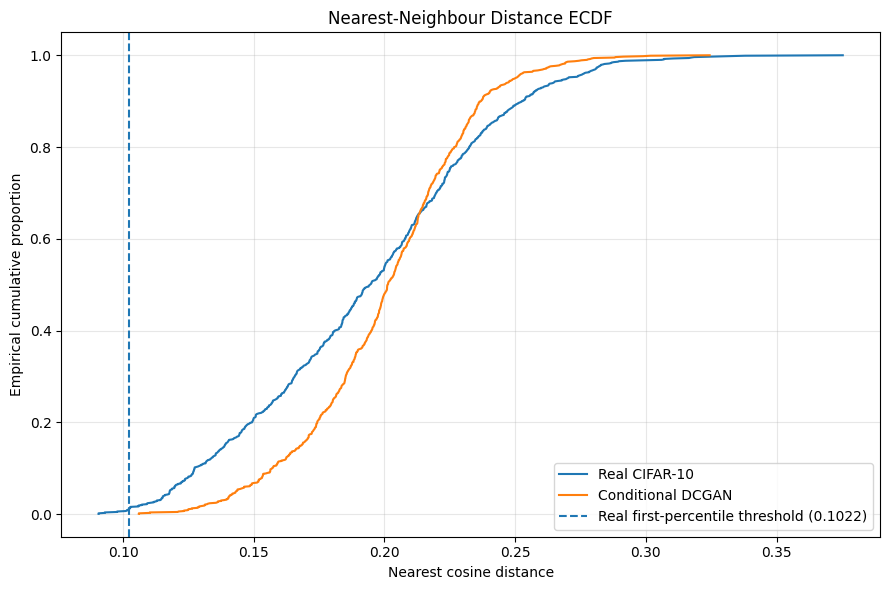

Representative real threshold: 0.102203
Generated samples below threshold: 0
Nearest-distance ECDF saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_nearest_distance_ecdf.png
Closest generated pairs are inspected next.
Protected test set remains unused.


In [91]:
required_conditional_ecdf_objects = [
    "CONDITIONAL_REPRESENTATIVE_REAL_NEAREST_DISTANCES",
    "CONDITIONAL_REPRESENTATIVE_GENERATED_NEAREST_DISTANCES",
    "CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_THRESHOLD",
    "CONDITIONAL_SEED42_RUN_ID",
    "GRIDS_DIR",
    "np",
    "plt",
]

missing_conditional_ecdf_objects = [
    name
    for name in required_conditional_ecdf_objects
    if name not in globals()
]

assert not missing_conditional_ecdf_objects, (
    "Incomplete conditional nearest-distance setup:\n"
    + "\n".join(
        missing_conditional_ecdf_objects
    )
)


conditional_real_nearest_distances = np.asarray(
    CONDITIONAL_REPRESENTATIVE_REAL_NEAREST_DISTANCES,
    dtype=np.float64,
)

conditional_generated_nearest_distances = np.asarray(
    CONDITIONAL_REPRESENTATIVE_GENERATED_NEAREST_DISTANCES,
    dtype=np.float64,
)

conditional_representative_threshold = float(
    CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_THRESHOLD
)


assert conditional_real_nearest_distances.shape == (
    CONDITIONAL_DIVERSITY_SUBSET_SIZE,
)

assert conditional_generated_nearest_distances.shape == (
    CONDITIONAL_DIVERSITY_SUBSET_SIZE,
)

assert np.isfinite(
    conditional_real_nearest_distances
).all()

assert np.isfinite(
    conditional_generated_nearest_distances
).all()


conditional_real_sorted = np.sort(
    conditional_real_nearest_distances
)

conditional_generated_sorted = np.sort(
    conditional_generated_nearest_distances
)

conditional_real_ecdf = (
    np.arange(
        1,
        len(conditional_real_sorted) + 1,
    )
    / len(conditional_real_sorted)
)

conditional_generated_ecdf = (
    np.arange(
        1,
        len(conditional_generated_sorted) + 1,
    )
    / len(conditional_generated_sorted)
)


CONDITIONAL_NEAREST_DISTANCE_ECDF_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "nearest_distance_ecdf.png"
    )
)


figure, axis = plt.subplots(
    figsize=(9, 6)
)

axis.plot(
    conditional_real_sorted,
    conditional_real_ecdf,
    label="Real CIFAR-10",
)

axis.plot(
    conditional_generated_sorted,
    conditional_generated_ecdf,
    label="Conditional DCGAN",
)

axis.axvline(
    conditional_representative_threshold,
    linestyle="--",
    label=(
        "Real first-percentile threshold "
        f"({conditional_representative_threshold:.4f})"
    ),
)

axis.set_title(
    "Nearest-Neighbour Distance ECDF"
)

axis.set_xlabel(
    "Nearest cosine distance"
)

axis.set_ylabel(
    "Empirical cumulative proportion"
)

axis.legend()
axis.grid(alpha=0.3)

figure.tight_layout()

figure.savefig(
    CONDITIONAL_NEAREST_DISTANCE_ECDF_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_COUNT = int(
    np.sum(
        conditional_generated_nearest_distances
        < conditional_representative_threshold
    )
)


print(
    "Representative real threshold:",
    f"{conditional_representative_threshold:.6f}",
)

print(
    "Generated samples below threshold:",
    CONDITIONAL_REPRESENTATIVE_NEAR_DUPLICATE_COUNT,
)

print(
    "Nearest-distance ECDF saved:",
    CONDITIONAL_NEAREST_DISTANCE_ECDF_PATH,
)

print(
    "Closest generated pairs are inspected next."
)

print("Protected test set remains unused.")

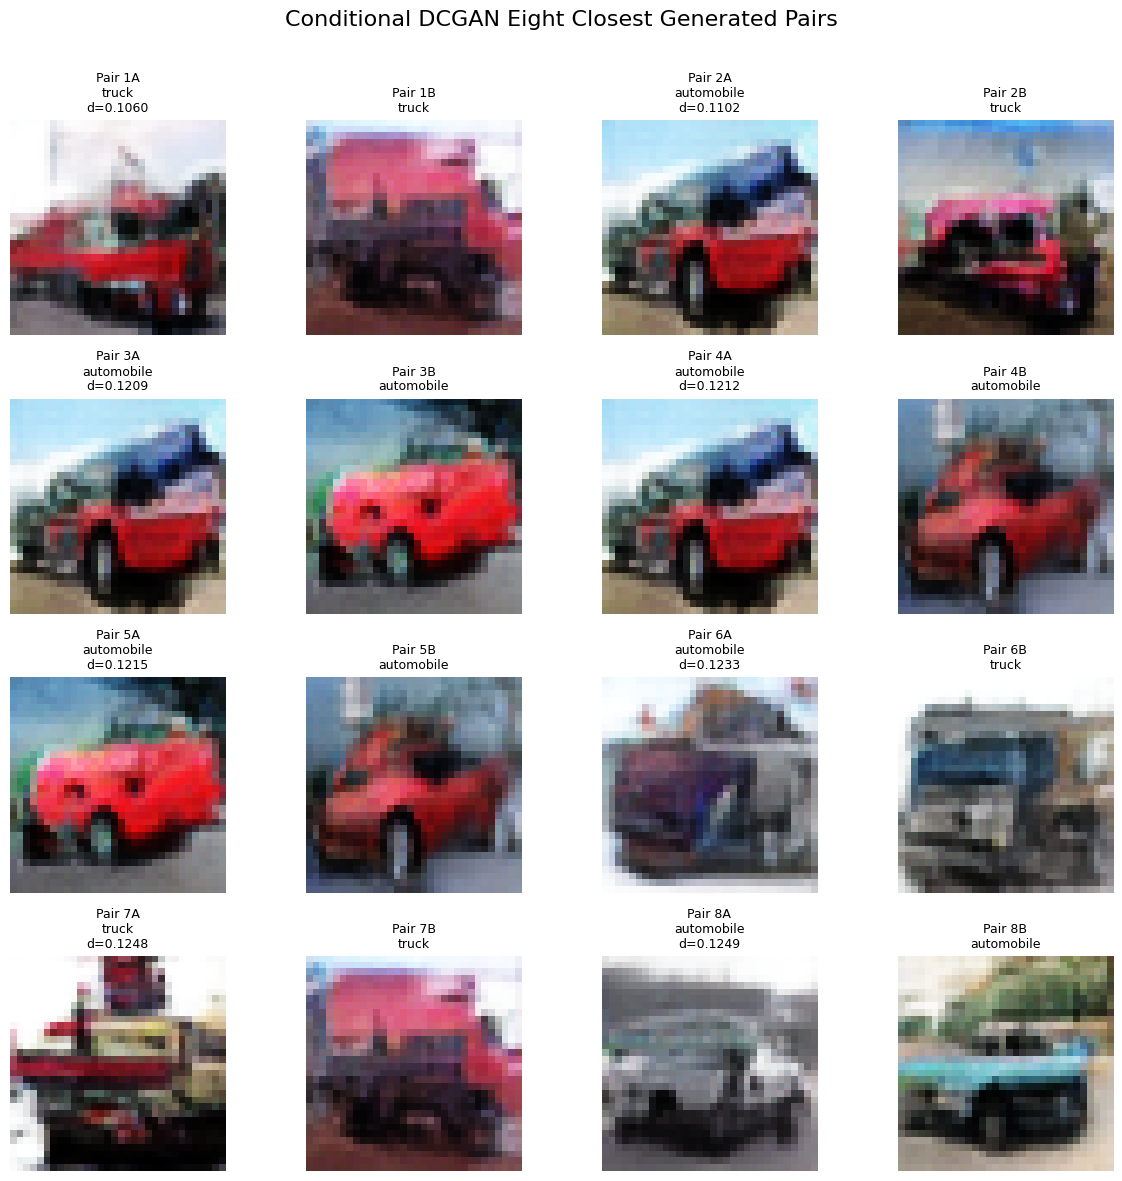

,Pair rank,Cosine distance,First pool index,First requested class,Second pool index,Second requested class,Same requested class
0,1,0.105995,4930,truck,4619,truck,True
1,2,0.110248,750,automobile,4647,truck,False
2,3,0.120918,750,automobile,676,automobile,True
3,4,0.121173,750,automobile,603,automobile,True
4,5,0.121505,676,automobile,603,automobile,True
5,6,0.123260,657,automobile,4759,truck,False
6,7,0.124775,4797,truck,4619,truck,True
7,8,0.124950,590,automobile,517,automobile,True


Closest-pair table saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_closest_generated_pairs.csv
Closest-pair figure saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_closest_generated_pairs.png
No generated-to-training memorisation comparison was performed.
Protected test set remains unused.


In [92]:
required_conditional_closest_pair_objects = [
    "conditional_automated_features",
    "conditional_automated_images",
    "conditional_automated_requested_labels",
    "CONDITIONAL_REPRESENTATIVE_GENERATED_INDICES",
    "CONDITIONAL_SEED42_RUN_ID",
    "CLASS_NAMES",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "np",
    "pd",
    "plt",
]

missing_conditional_closest_pair_objects = [
    name
    for name in required_conditional_closest_pair_objects
    if name not in globals()
]

assert not missing_conditional_closest_pair_objects, (
    "Incomplete conditional closest-pair setup:\n"
    + "\n".join(
        missing_conditional_closest_pair_objects
    )
)


conditional_representative_indices = np.asarray(
    CONDITIONAL_REPRESENTATIVE_GENERATED_INDICES,
    dtype=np.int64,
)

assert conditional_representative_indices.shape == (
    CONDITIONAL_DIVERSITY_SUBSET_SIZE,
)


conditional_representative_features = (
    conditional_automated_features[
        conditional_representative_indices
    ].astype(np.float64)
)


conditional_representative_norms = np.linalg.norm(
    conditional_representative_features,
    axis=1,
    keepdims=True,
)

assert (
    conditional_representative_norms
    > 0.0
).all()


conditional_representative_normalised_features = (
    conditional_representative_features
    / conditional_representative_norms
)


conditional_pairwise_cosine_distances = np.clip(
    1.0
    - (
        conditional_representative_normalised_features
        @ conditional_representative_normalised_features.T
    ),
    0.0,
    2.0,
)


upper_row_indices, upper_column_indices = np.triu_indices(
    CONDITIONAL_DIVERSITY_SUBSET_SIZE,
    k=1,
)

upper_pair_distances = (
    conditional_pairwise_cosine_distances[
        upper_row_indices,
        upper_column_indices,
    ]
)


CONDITIONAL_CLOSEST_PAIR_COUNT = 8

closest_pair_order = np.argsort(
    upper_pair_distances
)[:CONDITIONAL_CLOSEST_PAIR_COUNT]


conditional_closest_pair_rows = []


for pair_rank, pair_position in enumerate(
    closest_pair_order,
    start=1,
):
    local_index_a = int(
        upper_row_indices[pair_position]
    )

    local_index_b = int(
        upper_column_indices[pair_position]
    )

    global_index_a = int(
        conditional_representative_indices[
            local_index_a
        ]
    )

    global_index_b = int(
        conditional_representative_indices[
            local_index_b
        ]
    )

    class_index_a = int(
        conditional_automated_requested_labels[
            global_index_a
        ]
    )

    class_index_b = int(
        conditional_automated_requested_labels[
            global_index_b
        ]
    )


    conditional_closest_pair_rows.append(
        {
            "Pair rank": pair_rank,
            "Cosine distance": float(
                upper_pair_distances[
                    pair_position
                ]
            ),
            "First pool index": (
                global_index_a
            ),
            "First requested class": (
                CLASS_NAMES[
                    class_index_a
                ]
            ),
            "Second pool index": (
                global_index_b
            ),
            "Second requested class": (
                CLASS_NAMES[
                    class_index_b
                ]
            ),
            "Same requested class": bool(
                class_index_a == class_index_b
            ),
        }
    )


conditional_closest_pairs_df = pd.DataFrame(
    conditional_closest_pair_rows
)


CONDITIONAL_CLOSEST_PAIRS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "closest_generated_pairs.csv"
    )
)

CONDITIONAL_CLOSEST_PAIRS_FIGURE_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "closest_generated_pairs.png"
    )
)


conditional_closest_pairs_df.to_csv(
    CONDITIONAL_CLOSEST_PAIRS_PATH,
    index=False,
)


figure, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12),
    squeeze=False,
)


for pair_offset, pair_row in (
    conditional_closest_pairs_df.iterrows()
):
    display_row = pair_offset // 2
    display_pair_position = pair_offset % 2

    first_column = (
        display_pair_position * 2
    )

    second_column = (
        first_column + 1
    )


    first_index = int(
        pair_row[
            "First pool index"
        ]
    )

    second_index = int(
        pair_row[
            "Second pool index"
        ]
    )

    distance = float(
        pair_row[
            "Cosine distance"
        ]
    )


    axes[
        display_row,
        first_column,
    ].imshow(
        conditional_automated_images[
            first_index
        ]
    )

    axes[
        display_row,
        second_column,
    ].imshow(
        conditional_automated_images[
            second_index
        ]
    )


    axes[
        display_row,
        first_column,
    ].set_title(
        (
            f"Pair {pair_offset + 1}A\n"
            f"{pair_row['First requested class']}\n"
            f"d={distance:.4f}"
        ),
        fontsize=9,
    )

    axes[
        display_row,
        second_column,
    ].set_title(
        (
            f"Pair {pair_offset + 1}B\n"
            f"{pair_row['Second requested class']}"
        ),
        fontsize=9,
    )


    axes[
        display_row,
        first_column,
    ].axis("off")

    axes[
        display_row,
        second_column,
    ].axis("off")


figure.suptitle(
    "Conditional DCGAN Eight Closest Generated Pairs",
    fontsize=16,
)

figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.97)
)

figure.savefig(
    CONDITIONAL_CLOSEST_PAIRS_FIGURE_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


display(
    conditional_closest_pairs_df.round(6)
)


print(
    "Closest-pair table saved:",
    CONDITIONAL_CLOSEST_PAIRS_PATH,
)

print(
    "Closest-pair figure saved:",
    CONDITIONAL_CLOSEST_PAIRS_FIGURE_PATH,
)

print(
    "No generated-to-training "
    "memorisation comparison was performed."
)

print("Protected test set remains unused.")

### 13.15 Matched-Noise Label-Effect Analysis

The preceding adherence analyses show that requested labels and generated outputs are associated, but a conditional generator could still rely mainly on its latent vector while using labels only weakly.

A matched-noise evaluation therefore holds the latent vector fixed and changes only the requested class.

One hundred fixed latent vectors are each paired with all ten CIFAR-10 labels, producing `1,000` images.

The analysis compares:

- feature distance between different labels using the same latent vector;
- feature distance between different latent vectors using the same label;
- the number of distinct frozen-classifier predictions produced across the ten labels for each fixed latent vector;
- classifier agreement and mutual information on the matched-noise pool.

If labels were being ignored globally, changing the requested class while holding noise fixed would produce very small feature changes and few distinct predicted classes.

In [93]:
from sklearn.metrics import normalized_mutual_info_score


required_conditional_label_effect_objects = [
    "conditional_seed42_reloaded_generator",
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
    "make_stateless_noise",
    "extract_inception_features",
    "fid_feature_extractor",
    "CONDITIONAL_TIER1_LATENT_DIM",
    "CONDITIONAL_SEED42_RUN_ID",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "tf",
    "np",
    "pd",
    "plt",
]

missing_conditional_label_effect_objects = [
    name
    for name in required_conditional_label_effect_objects
    if name not in globals()
]

assert not missing_conditional_label_effect_objects, (
    "Incomplete matched-noise label-effect setup:\n"
    + "\n".join(
        missing_conditional_label_effect_objects
    )
)


assert COVERAGE_CLASSIFIER_FROZEN
assert coverage_classifier.trainable is False


CONDITIONAL_MATCHED_NOISE_SEED = 1503
CONDITIONAL_MATCHED_NOISE_COUNT = 100

CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT = (
    CONDITIONAL_MATCHED_NOISE_COUNT
    * NUM_CLASSES
)


conditional_matched_base_noise = make_stateless_noise(
    sample_count=(
        CONDITIONAL_MATCHED_NOISE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_TIER1_LATENT_DIM
    ),
    seed=(
        CONDITIONAL_MATCHED_NOISE_SEED
    ),
)


conditional_matched_noise = tf.repeat(
    conditional_matched_base_noise,
    repeats=NUM_CLASSES,
    axis=0,
)

conditional_matched_labels = tf.tile(
    tf.range(
        NUM_CLASSES,
        dtype=tf.int32,
    ),
    multiples=[
        CONDITIONAL_MATCHED_NOISE_COUNT
    ],
)

conditional_matched_labels = tf.reshape(
    conditional_matched_labels,
    (-1, 1),
)


assert conditional_matched_noise.shape == (
    CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    CONDITIONAL_TIER1_LATENT_DIM,
)

assert conditional_matched_labels.shape == (
    CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    1,
)


conditional_matched_generated_batches = []


for start_index in range(
    0,
    CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    256,
):
    end_index = min(
        start_index + 256,
        CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    )

    generated_batch = (
        conditional_seed42_reloaded_generator(
            [
                conditional_matched_noise[
                    start_index:end_index
                ],
                conditional_matched_labels[
                    start_index:end_index
                ],
            ],
            training=False,
        )
        .numpy()
    )

    conditional_matched_generated_batches.append(
        generated_batch
    )


conditional_matched_generated_float = np.concatenate(
    conditional_matched_generated_batches,
    axis=0,
)


conditional_matched_generated_uint8 = np.rint(
    np.clip(
        (
            conditional_matched_generated_float
            + 1.0
        )
        * 127.5,
        0.0,
        255.0,
    )
).astype(np.uint8)


assert conditional_matched_generated_uint8.shape == (
    CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    32,
    32,
    3,
)


conditional_matched_features = (
    extract_inception_features(
        images_uint8=(
            conditional_matched_generated_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=64,
    )
)


assert conditional_matched_features.shape == (
    CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT,
    2_048,
)


conditional_matched_probabilities = (
    coverage_classifier.predict(
        conditional_matched_generated_uint8,
        batch_size=256,
        verbose=0,
    )
)

conditional_matched_predictions = np.argmax(
    conditional_matched_probabilities,
    axis=1,
).astype(np.int64)

conditional_matched_requested_labels = (
    conditional_matched_labels
    .numpy()
    .reshape(-1)
    .astype(np.int64)
)


print(
    "Matched-noise evaluation pool created:",
    conditional_matched_generated_uint8.shape,
)

print(
    "Every latent vector was paired "
    "with all ten requested classes."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

Matched-noise evaluation pool created: (1000, 32, 32, 3)
Every latent vector was paired with all ten requested classes.
Protected test set remains unused.


In [94]:
conditional_matched_feature_tensor = (
    conditional_matched_features.reshape(
        CONDITIONAL_MATCHED_NOISE_COUNT,
        NUM_CLASSES,
        -1,
    )
)


conditional_matched_feature_norms = np.linalg.norm(
    conditional_matched_feature_tensor,
    axis=2,
    keepdims=True,
)

assert (
    conditional_matched_feature_norms
    > 0.0
).all()


conditional_matched_normalised_features = (
    conditional_matched_feature_tensor
    / conditional_matched_feature_norms
)


label_pair_rows, label_pair_columns = np.triu_indices(
    NUM_CLASSES,
    k=1,
)


same_noise_cross_label_distances = []


for noise_index in range(
    CONDITIONAL_MATCHED_NOISE_COUNT
):
    noise_feature_matrix = (
        conditional_matched_normalised_features[
            noise_index
        ]
    )

    noise_distance_matrix = np.clip(
        1.0
        - (
            noise_feature_matrix
            @ noise_feature_matrix.T
        ),
        0.0,
        2.0,
    )

    same_noise_cross_label_distances.append(
        float(
            noise_distance_matrix[
                label_pair_rows,
                label_pair_columns,
            ].mean()
        )
    )


same_label_cross_noise_distances = []


noise_pair_rows, noise_pair_columns = np.triu_indices(
    CONDITIONAL_MATCHED_NOISE_COUNT,
    k=1,
)


for class_index in range(
    NUM_CLASSES
):
    class_feature_matrix = (
        conditional_matched_normalised_features[
            :,
            class_index,
            :,
        ]
    )

    class_distance_matrix = np.clip(
        1.0
        - (
            class_feature_matrix
            @ class_feature_matrix.T
        ),
        0.0,
        2.0,
    )

    same_label_cross_noise_distances.append(
        float(
            class_distance_matrix[
                noise_pair_rows,
                noise_pair_columns,
            ].mean()
        )
    )


same_noise_cross_label_distances = np.asarray(
    same_noise_cross_label_distances,
    dtype=np.float64,
)

same_label_cross_noise_distances = np.asarray(
    same_label_cross_noise_distances,
    dtype=np.float64,
)


CONDITIONAL_SAME_NOISE_CROSS_LABEL_DISTANCE = float(
    same_noise_cross_label_distances.mean()
)

CONDITIONAL_SAME_LABEL_CROSS_NOISE_DISTANCE = float(
    same_label_cross_noise_distances.mean()
)

CONDITIONAL_LABEL_EFFECT_DISTANCE_RATIO = float(
    CONDITIONAL_SAME_NOISE_CROSS_LABEL_DISTANCE
    / CONDITIONAL_SAME_LABEL_CROSS_NOISE_DISTANCE
)


conditional_matched_prediction_matrix = (
    conditional_matched_predictions.reshape(
        CONDITIONAL_MATCHED_NOISE_COUNT,
        NUM_CLASSES,
    )
)

conditional_matched_unique_prediction_counts = np.array(
    [
        len(
            np.unique(
                prediction_row
            )
        )
        for prediction_row
        in conditional_matched_prediction_matrix
    ],
    dtype=np.int64,
)


CONDITIONAL_MATCHED_MEAN_UNIQUE_PREDICTIONS = float(
    conditional_matched_unique_prediction_counts.mean()
)

CONDITIONAL_MATCHED_CLASSIFIER_AGREEMENT = float(
    np.mean(
        conditional_matched_predictions
        == conditional_matched_requested_labels
    )
)

CONDITIONAL_MATCHED_NMI = float(
    normalized_mutual_info_score(
        conditional_matched_requested_labels,
        conditional_matched_predictions,
    )
)


conditional_matched_label_effect_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Noise seed": (
                CONDITIONAL_MATCHED_NOISE_SEED
            ),
            "Base noise count": (
                CONDITIONAL_MATCHED_NOISE_COUNT
            ),
            "Generated image count": (
                CONDITIONAL_MATCHED_NOISE_SAMPLE_COUNT
            ),
            "Mean same-noise cross-label distance": (
                CONDITIONAL_SAME_NOISE_CROSS_LABEL_DISTANCE
            ),
            "Mean same-label cross-noise distance": (
                CONDITIONAL_SAME_LABEL_CROSS_NOISE_DISTANCE
            ),
            "Cross-label to cross-noise distance ratio": (
                CONDITIONAL_LABEL_EFFECT_DISTANCE_RATIO
            ),
            "Mean unique classifier predictions per noise": (
                CONDITIONAL_MATCHED_MEAN_UNIQUE_PREDICTIONS
            ),
            "Matched-pool classifier agreement": (
                CONDITIONAL_MATCHED_CLASSIFIER_AGREEMENT
            ),
            "Matched-pool normalised mutual information": (
                CONDITIONAL_MATCHED_NMI
            ),
        }
    ]
)


CONDITIONAL_MATCHED_LABEL_EFFECT_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "matched_noise_label_effect.csv"
    )
)

CONDITIONAL_MATCHED_LABEL_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "matched_noise_label_grid.png"
    )
)


conditional_matched_label_effect_df.to_csv(
    CONDITIONAL_MATCHED_LABEL_EFFECT_PATH,
    index=False,
)


CONDITIONAL_MATCHED_GRID_NOISE_COUNT = 5


figure, axes = plt.subplots(
    NUM_CLASSES,
    CONDITIONAL_MATCHED_GRID_NOISE_COUNT,
    figsize=(12, 20),
    squeeze=False,
)


conditional_matched_image_tensor = (
    conditional_matched_generated_uint8.reshape(
        CONDITIONAL_MATCHED_NOISE_COUNT,
        NUM_CLASSES,
        32,
        32,
        3,
    )
)


for class_index in range(
    NUM_CLASSES
):
    for noise_index in range(
        CONDITIONAL_MATCHED_GRID_NOISE_COUNT
    ):
        axis = axes[
            class_index,
            noise_index,
        ]

        axis.imshow(
            conditional_matched_image_tensor[
                noise_index,
                class_index,
            ]
        )

        axis.axis("off")

        if noise_index == 0:
            axis.set_ylabel(
                CLASS_NAMES[
                    class_index
                ],
                rotation=0,
                labelpad=45,
                va="center",
                fontsize=10,
            )

        if class_index == 0:
            axis.set_title(
                f"Noise {noise_index + 1}",
                fontsize=10,
            )


figure.suptitle(
    (
        "Conditional DCGAN Matched-Noise "
        "Label-Effect Grid\n"
        "Columns Hold Noise Fixed, "
        "Rows Change Requested Class"
    ),
    fontsize=16,
)

figure.tight_layout(
    rect=(0.10, 0.0, 1.0, 0.965)
)

figure.savefig(
    CONDITIONAL_MATCHED_LABEL_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


display(
    conditional_matched_label_effect_df.round(6)
)


print(
    "Same-noise cross-label distance:",
    f"{CONDITIONAL_SAME_NOISE_CROSS_LABEL_DISTANCE:.6f}",
)

print(
    "Same-label cross-noise distance:",
    f"{CONDITIONAL_SAME_LABEL_CROSS_NOISE_DISTANCE:.6f}",
)

print(
    "Cross-label to cross-noise ratio:",
    f"{CONDITIONAL_LABEL_EFFECT_DISTANCE_RATIO:.6f}",
)

print(
    "Mean unique classifier predictions "
    "per fixed noise:",
    f"{CONDITIONAL_MATCHED_MEAN_UNIQUE_PREDICTIONS:.4f}",
)

print(
    "Matched-noise label-effect results saved:",
    CONDITIONAL_MATCHED_LABEL_EFFECT_PATH,
)

print(
    "Matched-noise grid saved:",
    CONDITIONAL_MATCHED_LABEL_GRID_PATH,
)

print(
    "No final label-ignoring conclusion "
    "has been recorded yet."
)

print("Protected test set remains unused.")

,Run ID,Noise seed,Base noise count,Generated image count,Mean same-noise cross-label distance,Mean same-label cross-noise distance,Cross-label to cross-noise distance ratio,Mean unique classifier predictions per noise,Matched-pool classifier agreement,Matched-pool normalised mutual information
0,G10_conditional_fliptranslation_seed42,1503,100,1000,0.297172,0.323958,0.917317,7.24,0.692,0.537241


Same-noise cross-label distance: 0.297172
Same-label cross-noise distance: 0.323958
Cross-label to cross-noise ratio: 0.917317
Mean unique classifier predictions per fixed noise: 7.2400
Matched-noise label-effect results saved: [local project directory]/histories/G10_conditional_fliptranslation_seed42_matched_noise_label_effect.csv
Matched-noise grid saved: [local project directory]/grids/G10_conditional_fliptranslation_seed42_matched_noise_label_grid.png
No final label-ignoring conclusion has been recorded yet.
Protected test set remains unused.


#### Nearest-Distance and Matched-Noise Interpretation

The conditional model passed the visual repetition safeguards.

In the representative diversity repeat, no generated sample fell below the real first-percentile nearest-neighbour threshold of approximately `0.1022`. The generated nearest-distance ECDF did not show an abnormal accumulation in the extreme low-distance tail.

The eight closest generated pairs were concentrated among automobiles and trucks. These pairs shared vehicle shape, colour and background themes, but they were not exact or near-exact copies. Several images appeared in more than one closest pair because they occupied a dense vehicle region in feature space.

The matched-noise grid provides direct evidence that the generator does not globally ignore its requested labels. Holding the latent vector fixed while changing the requested class produced clear changes in object category, especially between airplanes, road vehicles, animals and ships.

At the same time, each fixed latent vector retained similar composition, pose, background and colour characteristics across labels. This indicates that the latent vector primarily controls scene-level appearance while the label steers object identity.

Conditioning was less distinct among related animal classes. Cats, dogs, deer, frogs and horses sometimes retained similar quadruped structures under the same latent vector. The result is therefore interpreted as meaningful but imperfect class control rather than complete class separation.

Together with the balanced-pool classifier analysis, the matched-noise evidence rejects a global label-ignoring failure. It does not eliminate the previously observed ambiguity among related animal classes.

In [96]:
required_matched_noise_result_objects = [
    "CONDITIONAL_MATCHED_LABEL_EFFECT_PATH",
    "pd",
]

missing_matched_noise_result_objects = [
    name
    for name in required_matched_noise_result_objects
    if name not in globals()
]

assert not missing_matched_noise_result_objects, (
    "Incomplete matched-noise result setup:\n"
    + "\n".join(
        missing_matched_noise_result_objects
    )
)


assert CONDITIONAL_MATCHED_LABEL_EFFECT_PATH.is_file(), (
    "Missing matched-noise result:\n"
    f"{CONDITIONAL_MATCHED_LABEL_EFFECT_PATH}"
)


conditional_matched_label_effect_df = pd.read_csv(
    CONDITIONAL_MATCHED_LABEL_EFFECT_PATH
)


assert len(
    conditional_matched_label_effect_df
) == 1


display(
    conditional_matched_label_effect_df.round(6)
)


matched_noise_result_row = (
    conditional_matched_label_effect_df.iloc[0]
)


print(
    "Same-noise cross-label distance:",
    (
        f"{matched_noise_result_row[
            'Mean same-noise cross-label distance'
        ]:.6f}"
    ),
)

print(
    "Same-label cross-noise distance:",
    (
        f"{matched_noise_result_row[
            'Mean same-label cross-noise distance'
        ]:.6f}"
    ),
)

print(
    "Cross-label to cross-noise ratio:",
    (
        f"{matched_noise_result_row[
            'Cross-label to cross-noise distance ratio'
        ]:.6f}"
    ),
)

print(
    "Mean unique predictions per fixed noise:",
    (
        f"{matched_noise_result_row[
            'Mean unique classifier predictions per noise'
        ]:.4f}"
    ),
)

print(
    "Matched-pool classifier agreement:",
    (
        f"{matched_noise_result_row[
            'Matched-pool classifier agreement'
        ]:.4f}"
    ),
)

print(
    "Matched-pool NMI:",
    (
        f"{matched_noise_result_row[
            'Matched-pool normalised mutual information'
        ]:.4f}"
    ),
)

print("Protected test set remains unused.")

,Run ID,Noise seed,Base noise count,Generated image count,Mean same-noise cross-label distance,Mean same-label cross-noise distance,Cross-label to cross-noise distance ratio,Mean unique classifier predictions per noise,Matched-pool classifier agreement,Matched-pool normalised mutual information
0,G10_conditional_fliptranslation_seed42,1503,100,1000,0.297172,0.323958,0.917317,7.24,0.692,0.537241


Same-noise cross-label distance: 0.297172
Same-label cross-noise distance: 0.323958
Cross-label to cross-noise ratio: 0.917317
Mean unique predictions per fixed noise: 7.2400
Matched-pool classifier agreement: 0.6920
Matched-pool NMI: 0.5372
Protected test set remains unused.


### 13.16 Conditional Seed-123 Robustness Confirmation

The seed-42 conditional DCGAN remained a serious final-model candidate after its complete evaluation package.

Its repeated development FID and strict manual recognisability were practically tied with the selected unconditional DCGAN, while direct grids, frozen-classifier analysis and matched-noise analysis showed meaningful requested-class control. A second conditional training seed is therefore required to determine whether these findings are reasonably reproducible rather than specific to one favourable initialisation.

This run changes only the independent training seed from `42` to `123`. All modelling and optimisation choices remain fixed:

- the conditional generator and discriminator architectures;
- latent dimension `100`;
- label-embedding dimension `50`;
- batch size `64`;
- generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- one discriminator update followed by one generator update per batch;
- horizontal flipping and two-pixel translation;
- all `50,000` CIFAR-10 training images;
- `100` training epochs;
- milestone weights at epochs `50`, `70`, `90` and `100`;
- class-organised progression grids every ten epochs.

The augmentation policy receives seed `123`. Its translation layer consequently uses seed `124`, following the same run-seed convention as seed `42`.

Seed `123` receives a lean robustness package after training. Manual scoring, descriptor analysis and diversity analysis will only be repeated if its principal results materially contradict seed `42`.

The protected CIFAR-10 test set remains unused.

In [66]:
required_conditional_seed123_training_objects = [
    "PRIMARY_SEED",
    "SECONDARY_SEED",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "CONDITIONAL_LABEL_EMBEDDING_DIM",
    "CONDITIONAL_GENERATOR_PARAMETERS",
    "CONDITIONAL_DISCRIMINATOR_PARAMETERS",
    "x_train_gan",
    "y_train",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "build_dcgan_augmentation_policy",
    "make_conditional_training_dataset",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
    "make_conditional_dcgan_train_step",
    "make_conditional_fixed_grid_inputs",
    "save_conditional_class_grid",
    "save_conditional_checkpoint_and_grid",
    "train_or_resume_conditional_dcgan",
    "inspect_dcgan_training_status",
    "reset_run_seed",
]

missing_conditional_seed123_training_objects = [
    name
    for name
    in required_conditional_seed123_training_objects
    if name not in globals()
]

assert not missing_conditional_seed123_training_objects, (
    "Incomplete conditional seed-123 training setup:\n"
    + "\n".join(
        missing_conditional_seed123_training_objects
    )
)


CONDITIONAL_SEED123_RUN_ID = (
    "G11_conditional_fliptranslation_seed123"
)

CONDITIONAL_SEED123_LABEL = (
    "Conditional DCGAN, "
    "Flip + Translation, Seed 123"
)

CONDITIONAL_SEED123_TRAINING_SEED = (
    SECONDARY_SEED
)

CONDITIONAL_SEED123_AUGMENTATION_SEED = (
    CONDITIONAL_SEED123_TRAINING_SEED
)

CONDITIONAL_SEED123_TRANSLATION_SEED = (
    CONDITIONAL_SEED123_AUGMENTATION_SEED
    + 1
)

CONDITIONAL_SEED123_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

CONDITIONAL_SEED123_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

CONDITIONAL_SEED123_CHECKPOINT_INTERVAL = 10

CONDITIONAL_SEED123_FIXED_SAMPLES_PER_CLASS = 5

CONDITIONAL_SEED123_BATCHES_PER_EPOCH = int(
    np.ceil(
        len(x_train_gan)
        / CURRENT_BATCH_SIZE
    )
)

CONDITIONAL_SEED123_EXPECTED_UPDATES = int(
    CONDITIONAL_SEED123_BATCHES_PER_EPOCH
    * CONDITIONAL_SEED123_TARGET_EPOCHS
)


assert CONDITIONAL_SEED123_TRAINING_SEED == 123

assert CONDITIONAL_SEED123_TRANSLATION_SEED == 124

assert CURRENT_LATENT_DIM == 100
assert CURRENT_BATCH_SIZE == 64
assert CONDITIONAL_SEED123_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4
assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5
assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert (
    CONDITIONAL_SEED123_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert CONDITIONAL_SEED123_BATCHES_PER_EPOCH == 782

assert CONDITIONAL_SEED123_EXPECTED_UPDATES == 78_200

assert CONDITIONAL_GENERATOR_PARAMETERS == 1_290_487

assert CONDITIONAL_DISCRIMINATOR_PARAMETERS == 675_393


conditional_seed123_training_contract_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Training seed": (
                CONDITIONAL_SEED123_TRAINING_SEED
            ),
            "Augmentation seed": (
                CONDITIONAL_SEED123_AUGMENTATION_SEED
            ),
            "Translation seed": (
                CONDITIONAL_SEED123_TRANSLATION_SEED
            ),
            "Latent dimension": (
                CURRENT_LATENT_DIM
            ),
            "Label embedding dimension": (
                CONDITIONAL_LABEL_EMBEDDING_DIM
            ),
            "Batch size": (
                CURRENT_BATCH_SIZE
            ),
            "Generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Epochs": (
                CONDITIONAL_SEED123_TARGET_EPOCHS
            ),
            "Batches per epoch": (
                CONDITIONAL_SEED123_BATCHES_PER_EPOCH
            ),
            "Expected updates per network": (
                CONDITIONAL_SEED123_EXPECTED_UPDATES
            ),
            "Milestone epochs": str(
                CONDITIONAL_SEED123_MILESTONE_EPOCHS
            ),
            "Intentional change": (
                "Training seed only"
            ),
        }
    ]
)


display(
    conditional_seed123_training_contract_df
)


print(
    "Conditional seed-123 training "
    "contract validated."
)

print(
    "The existing conditional trainer "
    "will be reused unchanged."
)

print("Protected test set remains unused.")

,Run ID,Training seed,Augmentation seed,Translation seed,Latent dimension,Label embedding dimension,Batch size,Generator LR,Discriminator LR,Epochs,Batches per epoch,Expected updates per network,Milestone epochs,Intentional change
0,G11_conditional_fliptranslation_seed123,123,123,124,100,50,64,0.0002,0.0002,100,782,78200,"(50, 70, 90, 100)",Training seed only


Conditional seed-123 training contract validated.
The existing conditional trainer will be reused unchanged.
Protected test set remains unused.


In [69]:
keras.backend.clear_session()


conditional_seed123_training_summary = (
    train_or_resume_conditional_dcgan(
        run_id=CONDITIONAL_SEED123_RUN_ID,
        training_images=x_train_gan,
        training_labels=y_train,
        training_seed=(
            CONDITIONAL_SEED123_TRAINING_SEED
        ),
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=(
            CONDITIONAL_SEED123_TARGET_EPOCHS
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            CONDITIONAL_SEED123_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            CONDITIONAL_SEED123_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        fixed_samples_per_class=(
            CONDITIONAL_SEED123_FIXED_SAMPLES_PER_CLASS
        ),
        max_to_keep=3,
        model_label=(
            CONDITIONAL_SEED123_LABEL
        ),
    )
)


conditional_seed123_training_df = pd.DataFrame(
    [
        conditional_seed123_training_summary
    ]
)


display(
    conditional_seed123_training_df[
        [
            "run_id",
            "action",
            "restored_epoch",
            "epochs_trained_this_call",
            "epochs_completed",
            "batches_per_epoch",
            "generator_updates",
            "discriminator_updates",
            "generator_parameters",
            "discriminator_parameters",
            "training_time_minutes",
        ]
    ].round(4)
)


assert int(
    conditional_seed123_training_df[
        "epochs_completed"
    ].iloc[0]
) == CONDITIONAL_SEED123_TARGET_EPOCHS

assert int(
    conditional_seed123_training_df[
        "batches_per_epoch"
    ].iloc[0]
) == CONDITIONAL_SEED123_BATCHES_PER_EPOCH

assert int(
    conditional_seed123_training_df[
        "generator_updates"
    ].iloc[0]
) == CONDITIONAL_SEED123_EXPECTED_UPDATES

assert int(
    conditional_seed123_training_df[
        "discriminator_updates"
    ].iloc[0]
) == CONDITIONAL_SEED123_EXPECTED_UPDATES


print(
    "Conditional seed-123 training call completed."
)

print(
    "No seed-123 checkpoint has "
    "been selected yet."
)

print("Protected test set remains unused.")

Training new conditional run G11_conditional_fliptranslation_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.0951 | D loss: 0.1945 | Real: 0.8697 | Fake: 0.1270 | Time: 19.9s
Epoch 002/100 | G loss: 0.7739 | D loss: 0.2245 | Real: 0.8464 | Fake: 0.1522 | Time: 14.0s
Epoch 003/100 | G loss: 0.4970 | D loss: 0.1950 | Real: 0.8719 | Fake: 0.1272 | Time: 14.1s
Epoch 004/100 | G loss: 0.6890 | D loss: 0.2510 | Real: 0.8260 | Fake: 0.1737 | Time: 13.9s
Epoch 005/100 | G loss: 0.7285 | D loss: 0.2530 | Real: 0.8263 | Fake: 0.1718 | Time: 13.9s
Epoch 006/100 | G loss: 0.8128 | D loss: 0.2711 | Real: 0.8123 | Fake: 0.1864 | Time: 14.0s
Epoch 007/100 | G loss: 1.1281 | D loss: 0.3778 | Real: 0.7405 | Fake: 0.2586 | Time: 14.0s
Epoch 008/100 | G loss: 1.1139 | D loss: 0.4172 | Real: 0.7156 | Fake: 0.2824 | Time: 13.9s
Epoch 009/100 | G loss: 1.3838 | D loss: 0.4181 | Real: 0.7008 | Fake: 0.2967 | Time: 14.0s
Saved checkpoint: [local project directory]/checkpoints/G11_conditional_fliptransl

,run_id,action,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,generator_parameters,discriminator_parameters,training_time_minutes
0,G11_conditional_fliptranslation_seed123,trained_new,0,100,100,782,78200,78200,1290487,675393,23.4324


Conditional seed-123 training call completed.
No seed-123 checkpoint has been selected yet.
Protected test set remains unused.


#### Conditional Seed-123 Training Artifact Audit

The completed seed-123 run is audited before the L4 runtime is released.

The audit verifies:

- exactly `100` sequential and finite history rows;
- a recoverable epoch-100 checkpoint;
- ten class-organised progression grids;
- generator and discriminator milestone weights at epochs `50`, `70`, `90` and `100`;
- `782` batches per epoch;
- `78,200` updates per network;
- the expected conditional parameter counts;
- positive recorded training time.

This audit does not calculate FID or select a checkpoint.

In [70]:
required_conditional_seed123_audit_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TARGET_EPOCHS",
    "CONDITIONAL_SEED123_MILESTONE_EPOCHS",
    "CONDITIONAL_SEED123_CHECKPOINT_INTERVAL",
    "CONDITIONAL_SEED123_BATCHES_PER_EPOCH",
    "CONDITIONAL_SEED123_EXPECTED_UPDATES",
    "CONDITIONAL_GENERATOR_PARAMETERS",
    "CONDITIONAL_DISCRIMINATOR_PARAMETERS",
    "STANDARD_DCGAN_HISTORY_COLUMNS",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "inspect_dcgan_training_status",
]

missing_conditional_seed123_audit_objects = [
    name
    for name
    in required_conditional_seed123_audit_objects
    if name not in globals()
]

assert not missing_conditional_seed123_audit_objects, (
    "Incomplete conditional seed-123 audit setup:\n"
    + "\n".join(
        missing_conditional_seed123_audit_objects
    )
)


conditional_seed123_status = (
    inspect_dcgan_training_status(
        run_id=(
            CONDITIONAL_SEED123_RUN_ID
        ),
        target_epochs=(
            CONDITIONAL_SEED123_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            CONDITIONAL_SEED123_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            CONDITIONAL_SEED123_CHECKPOINT_INTERVAL
        ),
    )
)


assert (
    conditional_seed123_status["status"]
    == "completed"
)

assert (
    conditional_seed123_status[
        "checkpoint_epoch"
    ]
    == CONDITIONAL_SEED123_TARGET_EPOCHS
)


conditional_seed123_history_path = (
    HISTORIES_DIR
    / f"{CONDITIONAL_SEED123_RUN_ID}.csv"
)


assert conditional_seed123_history_path.is_file()


conditional_seed123_history_df = (
    pd.read_csv(
        conditional_seed123_history_path
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(
    conditional_seed123_history_df
) == CONDITIONAL_SEED123_TARGET_EPOCHS

assert np.array_equal(
    conditional_seed123_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        CONDITIONAL_SEED123_TARGET_EPOCHS + 1,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    conditional_seed123_history_df[
        STANDARD_DCGAN_HISTORY_COLUMNS
    ].to_numpy(dtype=np.float64)
).all()


conditional_seed123_progression_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        CONDITIONAL_SEED123_CHECKPOINT_INTERVAL,
        CONDITIONAL_SEED123_TARGET_EPOCHS + 1,
        CONDITIONAL_SEED123_CHECKPOINT_INTERVAL,
    )
}


conditional_seed123_generator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in CONDITIONAL_SEED123_MILESTONE_EPOCHS
}


conditional_seed123_discriminator_milestone_paths = {
    epoch: (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch
    in CONDITIONAL_SEED123_MILESTONE_EPOCHS
}


for path in (
    list(
        conditional_seed123_progression_paths.values()
    )
    + list(
        conditional_seed123_generator_milestone_paths.values()
    )
    + list(
        conditional_seed123_discriminator_milestone_paths.values()
    )
):
    assert path.is_file(), (
        "Missing conditional seed-123 artifact:\n"
        f"{path}"
    )

    assert path.stat().st_size > 0


assert len(
    conditional_seed123_progression_paths
) == 10

assert len(
    conditional_seed123_generator_milestone_paths
) == 4

assert len(
    conditional_seed123_discriminator_milestone_paths
) == 4


CONDITIONAL_SEED123_RUNTIME_MINUTES = float(
    conditional_seed123_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


assert CONDITIONAL_SEED123_RUNTIME_MINUTES > 0.0


conditional_seed123_artifact_audit_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Status": (
                conditional_seed123_status[
                    "status"
                ]
            ),
            "History rows": int(
                len(
                    conditional_seed123_history_df
                )
            ),
            "Checkpoint epoch": int(
                conditional_seed123_status[
                    "checkpoint_epoch"
                ]
            ),
            "Progression grids": int(
                len(
                    conditional_seed123_progression_paths
                )
            ),
            "Generator milestones": int(
                len(
                    conditional_seed123_generator_milestone_paths
                )
            ),
            "Discriminator milestones": int(
                len(
                    conditional_seed123_discriminator_milestone_paths
                )
            ),
            "Batches per epoch": (
                CONDITIONAL_SEED123_BATCHES_PER_EPOCH
            ),
            "Expected generator updates": (
                CONDITIONAL_SEED123_EXPECTED_UPDATES
            ),
            "Expected discriminator updates": (
                CONDITIONAL_SEED123_EXPECTED_UPDATES
            ),
            "Generator parameters": (
                CONDITIONAL_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CONDITIONAL_DISCRIMINATOR_PARAMETERS
            ),
            "Finite history": True,
            "Training time minutes": (
                CONDITIONAL_SEED123_RUNTIME_MINUTES
            ),
            "Audit passed": True,
        }
    ]
)


CONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "artifact_audit.csv"
    )
)


conditional_seed123_artifact_audit_df.to_csv(
    CONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    conditional_seed123_artifact_audit_df.round(4)
)


print(
    "Conditional seed-123 artifact audit passed."
)

print(
    "Artifact audit saved:",
    CONDITIONAL_SEED123_ARTIFACT_AUDIT_PATH,
)

print(
    "Milestone FID and checkpoint selection "
    "remain pending."
)

print(
    "The L4 runtime may now be released."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Expected generator updates,Expected discriminator updates,Generator parameters,Discriminator parameters,Finite history,Training time minutes,Audit passed
0,G11_conditional_fliptranslation_seed123,completed,100,100,10,4,4,782,78200,78200,1290487,675393,True,23.4324,True


Conditional seed-123 artifact audit passed.
Artifact audit saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_artifact_audit.csv
Milestone FID and checkpoint selection remain pending.
The L4 runtime may now be released.
Protected test set remains unused.


### 13.17 Conditional Seed-123 Tier 1 Evaluation

The completed conditional seed-123 run now receives its first evaluation tier.

Tier 1 examines:

- the complete training trajectory;
- late-training adversarial balance;
- class-organised progression grids at epochs `50`, `70`, `90` and `100`;
- development FID at the four saved milestone checkpoints.

For each milestone FID calculation, the generator will produce `5,000` images using fixed seed `1001`, with exactly `500` requested samples from each CIFAR-10 class.

This stage screens for collapse, severe deterioration, unstable late training and clearly weak milestones. It does not yet select a checkpoint or perform repeated FID, formal manual scoring, descriptor analysis or diversity evaluation.

The protected CIFAR-10 test set remains unused.

In [71]:
required_conditional_seed123_tier1_objects = [
    "np",
    "pd",
    "plt",
    "Path",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TRAINING_SEED",
    "CONDITIONAL_SEED123_MILESTONE_EPOCHS",
]

missing_conditional_seed123_tier1_objects = [
    name
    for name
    in required_conditional_seed123_tier1_objects
    if name not in globals()
]

assert not missing_conditional_seed123_tier1_objects, (
    "Incomplete conditional seed-123 "
    "Tier 1 setup:\n"
    + "\n".join(
        missing_conditional_seed123_tier1_objects
    )
)


CONDITIONAL_SEED123_TIER1_LATENT_DIM = 100

CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM = 50

CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS = (
    CONDITIONAL_SEED123_MILESTONE_EPOCHS
)

CONDITIONAL_SEED123_TIER1_FID_SEED = 1001

CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT = 5_000

CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE = 64

CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS = (
    CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
    // NUM_CLASSES
)


assert NUM_CLASSES == 10
assert len(CLASS_NAMES) == 10

assert CONDITIONAL_SEED123_TIER1_LATENT_DIM == 100

assert (
    CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert (
    CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
    % NUM_CLASSES
    == 0
)

assert (
    CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
    == 500
)


conditional_seed123_tier1_contract_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Training seed": (
                CONDITIONAL_SEED123_TRAINING_SEED
            ),
            "Milestone epochs": str(
                CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS
            ),
            "FID seed": (
                CONDITIONAL_SEED123_TIER1_FID_SEED
            ),
            "FID sample count": (
                CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
            ),
            "Checkpoint selected": False,
        }
    ]
)


display(
    conditional_seed123_tier1_contract_df
)


print(
    "Conditional seed-123 Tier 1 "
    "contract validated."
)

print(
    "No checkpoint has been selected."
)

print(
    "Protected test set remains unused."
)

,Run ID,Training seed,Milestone epochs,FID seed,FID sample count,Samples per requested class,Checkpoint selected
0,G11_conditional_fliptranslation_seed123,123,"(50, 70, 90, 100)",1001,5000,500,False


Conditional seed-123 Tier 1 contract validated.
No checkpoint has been selected.
Protected test set remains unused.


#### Training Trajectory and Late-Stability Review

The complete 100-epoch history is reviewed in five 20-epoch phases.

Generator loss, discriminator loss, real score, fake score and real-minus-fake score separation are summarised to determine whether the second conditional run remained finite and stable or showed severe late deterioration.

These values are diagnostic only. A stronger discriminator does not independently prove worse generated-image quality. Milestone grids and FID are required before selecting a checkpoint.

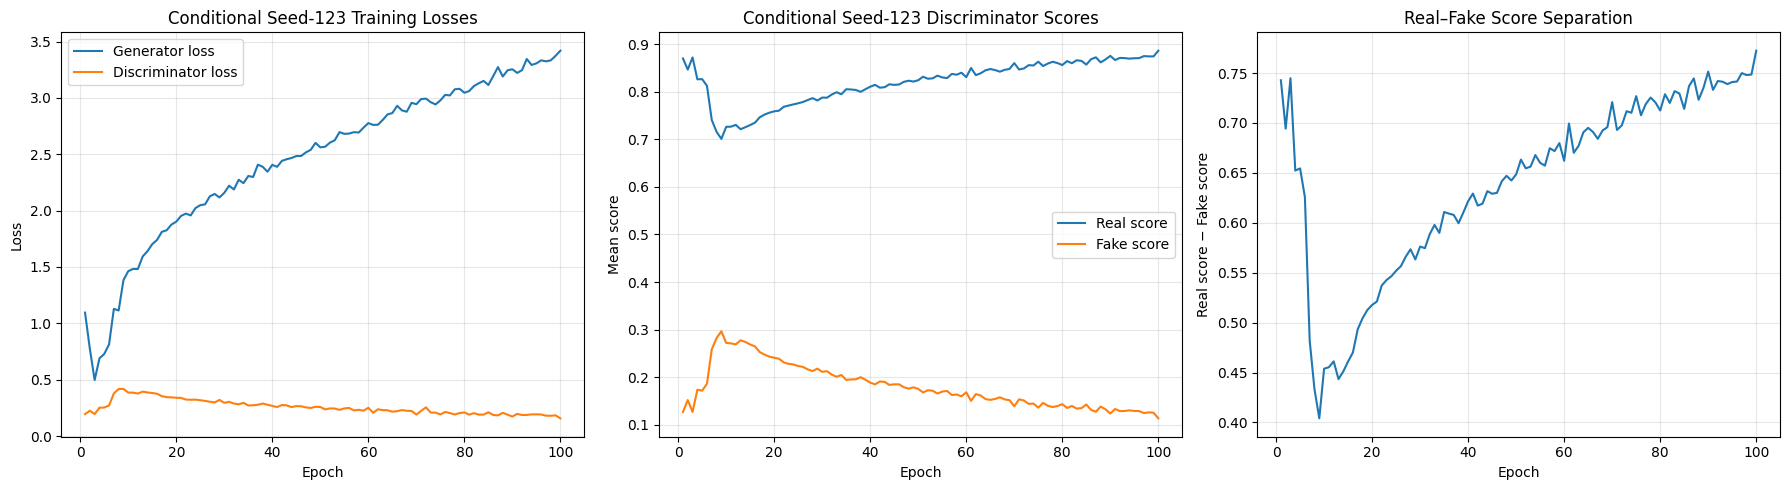

,Epoch phase,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean seconds
0,1-20,1.3371,0.4489,0.3334,0.0733,0.7658,0.2329,0.5329,14.2565
1,21-40,2.1821,0.1502,0.2987,0.0208,0.7884,0.2111,0.5773,13.9107
2,41-60,2.5850,0.1111,0.2498,0.0142,0.8244,0.1752,0.6492,13.9462
3,61-80,2.9382,0.0955,0.2156,0.0164,0.8509,0.1488,0.7020,13.9400
4,81-100,3.2457,0.0985,0.1884,0.0116,0.8692,0.1306,0.7386,14.2439


Late epoch-81-to-100 score separation: 0.7386
Recorded training runtime: 23.4324 minutes
Stability summary saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_tier1_stability_summary.csv
Training curves saved: [local project directory]/grids/G11_conditional_fliptranslation_seed123_tier1_training_curves.png
Visual and FID evidence are still required before checkpoint selection.
Protected test set remains unused.


In [72]:
conditional_seed123_history_path = (
    HISTORIES_DIR
    / f"{CONDITIONAL_SEED123_RUN_ID}.csv"
)


assert conditional_seed123_history_path.is_file(), (
    "Missing conditional seed-123 history:\n"
    f"{conditional_seed123_history_path}"
)


conditional_seed123_history_df = (
    pd.read_csv(
        conditional_seed123_history_path
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


conditional_seed123_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


missing_conditional_seed123_history_columns = [
    column
    for column
    in conditional_seed123_history_columns
    if column
    not in conditional_seed123_history_df.columns
]


assert not missing_conditional_seed123_history_columns, (
    "Conditional seed-123 history "
    "is missing:\n"
    + "\n".join(
        missing_conditional_seed123_history_columns
    )
)


assert len(
    conditional_seed123_history_df
) == 100


assert np.array_equal(
    conditional_seed123_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        101,
        dtype=np.int64,
    ),
)


assert np.isfinite(
    conditional_seed123_history_df[
        conditional_seed123_history_columns
    ].to_numpy(dtype=np.float64)
).all()


conditional_seed123_history_df[
    "score_separation"
] = (
    conditional_seed123_history_df[
        "real_score"
    ]
    - conditional_seed123_history_df[
        "fake_score"
    ]
)


conditional_seed123_phase_specs = [
    (1, 20),
    (21, 40),
    (41, 60),
    (61, 80),
    (81, 100),
]


conditional_seed123_phase_rows = []


for start_epoch, end_epoch in (
    conditional_seed123_phase_specs
):
    phase_df = (
        conditional_seed123_history_df.loc[
            conditional_seed123_history_df[
                "epoch"
            ].between(
                start_epoch,
                end_epoch,
                inclusive="both",
            )
        ]
    )


    assert len(phase_df) == 20


    conditional_seed123_phase_rows.append(
        {
            "Epoch phase": (
                f"{start_epoch}-{end_epoch}"
            ),
            "Generator loss mean": float(
                phase_df[
                    "generator_loss"
                ].mean()
            ),
            "Generator loss SD": float(
                phase_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Discriminator loss mean": float(
                phase_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Discriminator loss SD": float(
                phase_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Real score mean": float(
                phase_df[
                    "real_score"
                ].mean()
            ),
            "Fake score mean": float(
                phase_df[
                    "fake_score"
                ].mean()
            ),
            "Score separation mean": float(
                phase_df[
                    "score_separation"
                ].mean()
            ),
            "Epoch time mean seconds": float(
                phase_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


conditional_seed123_stability_df = (
    pd.DataFrame(
        conditional_seed123_phase_rows
    )
)


CONDITIONAL_SEED123_STABILITY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "tier1_stability_summary.csv"
    )
)

CONDITIONAL_SEED123_CURVES_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "tier1_training_curves.png"
    )
)


conditional_seed123_stability_df.to_csv(
    CONDITIONAL_SEED123_STABILITY_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


axes[0].plot(
    conditional_seed123_history_df[
        "epoch"
    ],
    conditional_seed123_history_df[
        "generator_loss"
    ],
    label="Generator loss",
)

axes[0].plot(
    conditional_seed123_history_df[
        "epoch"
    ],
    conditional_seed123_history_df[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

axes[0].set_title(
    "Conditional Seed-123 Training Losses"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    conditional_seed123_history_df[
        "epoch"
    ],
    conditional_seed123_history_df[
        "real_score"
    ],
    label="Real score",
)

axes[1].plot(
    conditional_seed123_history_df[
        "epoch"
    ],
    conditional_seed123_history_df[
        "fake_score"
    ],
    label="Fake score",
)

axes[1].set_title(
    "Conditional Seed-123 "
    "Discriminator Scores"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].plot(
    conditional_seed123_history_df[
        "epoch"
    ],
    conditional_seed123_history_df[
        "score_separation"
    ],
)

axes[2].set_title(
    "Real–Fake Score Separation"
)

axes[2].set_xlabel("Epoch")

axes[2].set_ylabel(
    "Real score − Fake score"
)

axes[2].grid(alpha=0.3)


figure.tight_layout()


figure.savefig(
    CONDITIONAL_SEED123_CURVES_PATH,
    dpi=160,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


display(
    conditional_seed123_stability_df.round(4)
)


conditional_seed123_late_df = (
    conditional_seed123_history_df.loc[
        conditional_seed123_history_df[
            "epoch"
        ].between(
            81,
            100,
            inclusive="both",
        )
    ]
)


CONDITIONAL_SEED123_LATE_SEPARATION = float(
    conditional_seed123_late_df[
        "score_separation"
    ].mean()
)


CONDITIONAL_SEED123_RUNTIME_MINUTES = float(
    conditional_seed123_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


print(
    "Late epoch-81-to-100 score separation:",
    f"{CONDITIONAL_SEED123_LATE_SEPARATION:.4f}",
)

print(
    "Recorded training runtime:",
    f"{CONDITIONAL_SEED123_RUNTIME_MINUTES:.4f}",
    "minutes",
)

print(
    "Stability summary saved:",
    CONDITIONAL_SEED123_STABILITY_PATH,
)

print(
    "Training curves saved:",
    CONDITIONAL_SEED123_CURVES_PATH,
)

print(
    "Visual and FID evidence are still "
    "required before checkpoint selection."
)

print(
    "Protected test set remains unused."
)

#### Class-Organised Milestone Progression

The saved class-organised grids from epochs `50`, `70`, `90` and `100` are displayed directly from Drive.

Each row corresponds to one requested CIFAR-10 class, and the same five latent vectors are reused across all classes and milestones.

The review checks for:

- broad class differentiation;
- ignored or weak conditioning;
- severe repetition;
- mode collapse;
- late visual deterioration;
- improvements that continue after epoch `50`.

No checkpoint-selection decision is made from these grids alone.

In [73]:
conditional_seed123_tier1_grid_paths = {
    epoch: (
        GRIDS_DIR
        / (
            f"{CONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS
}


for epoch, grid_path in (
    conditional_seed123_tier1_grid_paths.items()
):
    assert grid_path.is_file(), (
        f"Missing epoch-{epoch} "
        "conditional seed-123 grid:\n"
        f"{grid_path}"
    )

    assert grid_path.stat().st_size > 0


figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 20),
)


for axis, epoch in zip(
    axes.flat,
    CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS,
):
    grid_path = (
        conditional_seed123_tier1_grid_paths[
            epoch
        ]
    )

    axis.imshow(
        plt.imread(
            grid_path
        )
    )

    axis.set_title(
        f"Epoch {epoch}",
        fontsize=14,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Conditional DCGAN Seed-123 "
        "Class-Organised Milestone Progression"
    ),
    fontsize=17,
)


figure.tight_layout(
    rect=(0, 0, 1, 0.98)
)


plt.show()
plt.close(figure)


print(
    "Conditional seed-123 milestone "
    "grids displayed:",
    CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS,
)

print(
    "No visual-veto or checkpoint-selection "
    "decision has been recorded yet."
)

print(
    "Next step: calculate balanced "
    "milestone FID."
)

print(
    "Protected test set remains unused."
)

Conditional seed-123 milestone grids displayed: (50, 70, 90, 100)
No visual-veto or checkpoint-selection decision has been recorded yet.
Next step: calculate balanced milestone FID.
Protected test set remains unused.


#### Balanced Conditional Seed-123 Milestone FID

Each saved seed-123 milestone generator is evaluated using the same conditional FID protocol applied to seed `42`.

For every checkpoint:

- `5,000` unaugmented generated images are produced;
- generation uses fixed seed `1001`;
- exactly `500` images are requested from each CIFAR-10 class;
- generated images are converted to RGB `uint8 [0, 255]`;
- features are extracted using the frozen InceptionV3 feature extractor;
- FID is calculated against the complete 50,000-image CIFAR-10 training-reference statistics.

The milestone with the lowest FID becomes the provisional checkpoint. It will only be selected if the preceding visual and stability review provides no veto.

Repeated FID is not calculated at this stage.

The protected CIFAR-10 test set remains unused.

In [76]:
required_conditional_seed123_fid_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM",
    "CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS",
    "CONDITIONAL_SEED123_TIER1_FID_SEED",
    "CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT",
    "CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE",
    "CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS",
    "NUM_CLASSES",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "build_conditional_dcgan_generator",
    "generate_balanced_conditional_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "np",
    "pd",
    "gc",
]

missing_conditional_seed123_fid_objects = [
    name
    for name in required_conditional_seed123_fid_objects
    if name not in globals()
]

assert not missing_conditional_seed123_fid_objects, (
    "Incomplete conditional seed-123 "
    "milestone-FID setup:\n"
    + "\n".join(
        missing_conditional_seed123_fid_objects
    )
)


conditional_seed123_tier1_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_SEED123_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)


assert int(
    conditional_seed123_tier1_generator.count_params()
) == 1_290_487


conditional_seed123_tier1_fid_rows = []


for milestone_epoch in (
    CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS
):
    milestone_generator_path = (
        WEIGHTS_DIR
        / (
            f"{CONDITIONAL_SEED123_RUN_ID}_"
            f"epoch{milestone_epoch:03d}_"
            "generator.weights.h5"
        )
    )


    assert milestone_generator_path.is_file(), (
        f"Missing epoch-{milestone_epoch} "
        "seed-123 generator weights:\n"
        f"{milestone_generator_path}"
    )


    conditional_seed123_tier1_generator.load_weights(
        milestone_generator_path
    )


    (
        conditional_seed123_milestone_images_uint8,
        conditional_seed123_milestone_labels,
    ) = generate_balanced_conditional_images_uint8(
        generator=(
            conditional_seed123_tier1_generator
        ),
        sample_count=(
            CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            CONDITIONAL_SEED123_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        seed=(
            CONDITIONAL_SEED123_TIER1_FID_SEED
        ),
        batch_size=(
            CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE
        ),
    )


    assert (
        conditional_seed123_milestone_images_uint8.shape
        == (
            CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT,
            32,
            32,
            3,
        )
    )

    assert np.array_equal(
        np.bincount(
            conditional_seed123_milestone_labels.reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS,
            dtype=np.int64,
        ),
    )


    conditional_seed123_milestone_features = (
        extract_inception_features(
            images_uint8=(
                conditional_seed123_milestone_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE
            ),
        )
    )


    (
        conditional_seed123_milestone_mean,
        conditional_seed123_milestone_covariance,
    ) = calculate_feature_statistics(
        conditional_seed123_milestone_features
    )


    conditional_seed123_milestone_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            conditional_seed123_milestone_mean,
            conditional_seed123_milestone_covariance,
        )
    )


    assert np.isfinite(
        conditional_seed123_milestone_fid
    )

    assert (
        conditional_seed123_milestone_fid
        >= 0.0
    )


    conditional_seed123_tier1_fid_rows.append(
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Evaluation": (
                "milestone_fid"
            ),
            "Epoch": milestone_epoch,
            "Seed": (
                CONDITIONAL_SEED123_TIER1_FID_SEED
            ),
            "Sample count": (
                CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
            ),
            "FID": (
                conditional_seed123_milestone_fid
            ),
        }
    )


    print(
        f"Epoch {milestone_epoch:03d} "
        "conditional seed-123 FID: "
        f"{conditional_seed123_milestone_fid:.4f}"
    )


    del conditional_seed123_milestone_images_uint8
    del conditional_seed123_milestone_labels
    del conditional_seed123_milestone_features

    del conditional_seed123_milestone_mean
    del conditional_seed123_milestone_covariance

    gc.collect()


conditional_seed123_tier1_fid_df = pd.DataFrame(
    conditional_seed123_tier1_fid_rows
)


CONDITIONAL_SEED123_TIER1_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "milestone_fid.csv"
    )
)


conditional_seed123_tier1_fid_df.to_csv(
    CONDITIONAL_SEED123_TIER1_FID_RESULTS_PATH,
    index=False,
)


CONDITIONAL_SEED123_TIER1_LOWEST_FID_EPOCH = int(
    conditional_seed123_tier1_fid_df.loc[
        conditional_seed123_tier1_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)


CONDITIONAL_SEED123_TIER1_LOWEST_FID = float(
    conditional_seed123_tier1_fid_df[
        "FID"
    ].min()
)


display(
    conditional_seed123_tier1_fid_df.round(4)
)


print(
    "Lowest milestone FID epoch:",
    CONDITIONAL_SEED123_TIER1_LOWEST_FID_EPOCH,
)

print(
    "Lowest milestone FID:",
    f"{CONDITIONAL_SEED123_TIER1_LOWEST_FID:.4f}",
)

print(
    "Milestone FID results saved:",
    CONDITIONAL_SEED123_TIER1_FID_RESULTS_PATH,
)

print(
    "This remains a screening result."
)

print(
    "Checkpoint selection still requires "
    "the combined FID, visual and stability decision."
)

print(
    "Repeated FID has not been calculated."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 conditional seed-123 FID: 46.0153


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 conditional seed-123 FID: 39.2618


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 conditional seed-123 FID: 36.6495


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 conditional seed-123 FID: 34.3290


,Run ID,Evaluation,Epoch,Seed,Sample count,Samples per requested class,FID
0,G11_conditional_fliptranslation_seed123,milestone_fid,50,1001,5000,500,46.0153
1,G11_conditional_fliptranslation_seed123,milestone_fid,70,1001,5000,500,39.2618
2,G11_conditional_fliptranslation_seed123,milestone_fid,90,1001,5000,500,36.6495
3,G11_conditional_fliptranslation_seed123,milestone_fid,100,1001,5000,500,34.3290


Lowest milestone FID epoch: 100
Lowest milestone FID: 34.3290
Milestone FID results saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_milestone_fid.csv
This remains a screening result.
Checkpoint selection still requires the combined FID, visual and stability decision.
Repeated FID has not been calculated.
Protected test set remains unused.


### 13.18 Conditional Seed-123 Checkpoint Selection

The conditional seed-123 milestone FID improved at every evaluated checkpoint:

| Epoch | Development FID |
|---:|---:|
| 50 | 46.0153 |
| 70 | 39.2618 |
| 90 | 36.6495 |
| 100 | **34.3290** |

The class-organised progression grids also improved through epoch `100`, with no obvious mode collapse, severe repetition, ignored-label failure or late qualitative deterioration.

The discriminator became progressively stronger, with mean real-minus-fake score separation reaching `0.7386` during epochs `81–100`. However, the history remained finite and stable, and the increasing separation coincided with continued visual and FID improvement rather than deterioration.

No visual or stability override is therefore justified.

Epoch `100` is selected independently as the conditional seed-123 checkpoint.

Its single-seed screening FID is close to the seed-42 conditional result, but repeated FID is still required before judging seed robustness or comparing the two conditional runs.

In [77]:
required_conditional_seed123_selection_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TRAINING_SEED",
    "CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS",
    "CONDITIONAL_SEED123_TIER1_FID_RESULTS_PATH",
    "CONDITIONAL_SEED123_LATE_SEPARATION",
    "CONDITIONAL_SEED123_RUNTIME_MINUTES",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_seed123_selection_objects = [
    name
    for name
    in required_conditional_seed123_selection_objects
    if name not in globals()
]

assert not missing_conditional_seed123_selection_objects, (
    "Incomplete conditional seed-123 "
    "checkpoint-selection setup:\n"
    + "\n".join(
        missing_conditional_seed123_selection_objects
    )
)


conditional_seed123_milestone_fid_df = pd.read_csv(
    CONDITIONAL_SEED123_TIER1_FID_RESULTS_PATH
)


assert set(
    conditional_seed123_milestone_fid_df[
        "Epoch"
    ].astype(int)
) == set(
    CONDITIONAL_SEED123_TIER1_MILESTONE_EPOCHS
)

assert np.isfinite(
    conditional_seed123_milestone_fid_df[
        "FID"
    ].to_numpy(dtype=np.float64)
).all()


CONDITIONAL_SEED123_SELECTED_EPOCH = int(
    conditional_seed123_milestone_fid_df.loc[
        conditional_seed123_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

CONDITIONAL_SEED123_SELECTED_MILESTONE_FID = float(
    conditional_seed123_milestone_fid_df[
        "FID"
    ].min()
)


assert CONDITIONAL_SEED123_SELECTED_EPOCH == 100

assert (
    CONDITIONAL_SEED123_SELECTED_MILESTONE_FID
    < float(
        conditional_seed123_milestone_fid_df.loc[
            conditional_seed123_milestone_fid_df[
                "Epoch"
            ]
            == 90,
            "FID",
        ].iloc[0]
    )
)


CONDITIONAL_SEED123_VISUAL_VETO = False

CONDITIONAL_SEED123_STABILITY_VETO = False

CONDITIONAL_SEED123_SELECTION_OVERRIDE = False


CONDITIONAL_SEED123_SELECTED_MILESTONE_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        f"epoch{CONDITIONAL_SEED123_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

CONDITIONAL_SEED123_SELECTED_MILESTONE_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        f"epoch{CONDITIONAL_SEED123_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


assert (
    CONDITIONAL_SEED123_SELECTED_MILESTONE_GENERATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED123_SELECTED_MILESTONE_DISCRIMINATOR_PATH
    .is_file()
)


conditional_seed123_checkpoint_selection_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Training seed": (
                CONDITIONAL_SEED123_TRAINING_SEED
            ),
            "Selected epoch": (
                CONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                CONDITIONAL_SEED123_SELECTED_MILESTONE_FID
            ),
            "Late score separation": (
                CONDITIONAL_SEED123_LATE_SEPARATION
            ),
            "Training time minutes": (
                CONDITIONAL_SEED123_RUNTIME_MINUTES
            ),
            "Visual veto": (
                CONDITIONAL_SEED123_VISUAL_VETO
            ),
            "Stability veto": (
                CONDITIONAL_SEED123_STABILITY_VETO
            ),
            "Selection override": (
                CONDITIONAL_SEED123_SELECTION_OVERRIDE
            ),
            "Decision": (
                "Epoch 100 selected because it achieved "
                "the lowest milestone FID, continued the "
                "visible progression improvement and showed "
                "no collapse or late qualitative deterioration."
            ),
            "Repeated FID completed": False,
            "Conditional adherence completed": False,
        }
    ]
)


CONDITIONAL_SEED123_CHECKPOINT_SELECTION_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "checkpoint_selection.csv"
    )
)


conditional_seed123_checkpoint_selection_df.to_csv(
    CONDITIONAL_SEED123_CHECKPOINT_SELECTION_PATH,
    index=False,
)


display(
    conditional_seed123_checkpoint_selection_df.round(4)
)


print(
    "Selected conditional seed-123 epoch:",
    CONDITIONAL_SEED123_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{CONDITIONAL_SEED123_SELECTED_MILESTONE_FID:.4f}",
)

print(
    "Visual veto:",
    CONDITIONAL_SEED123_VISUAL_VETO,
)

print(
    "Stability veto:",
    CONDITIONAL_SEED123_STABILITY_VETO,
)

print(
    "Selection override:",
    CONDITIONAL_SEED123_SELECTION_OVERRIDE,
)

print(
    "Checkpoint-selection result saved:",
    CONDITIONAL_SEED123_CHECKPOINT_SELECTION_PATH,
)

print("Protected test set remains unused.")

,Run ID,Training seed,Selected epoch,Selected milestone FID,Late score separation,Training time minutes,Visual veto,Stability veto,Selection override,Decision,Repeated FID completed,Conditional adherence completed
0,G11_conditional_fliptranslation_seed123,123,100,34.329,0.7386,23.4324,False,False,False,Epoch 100 selected because it achieved the low...,False,False


Selected conditional seed-123 epoch: 100
Selected milestone FID: 34.3290
Visual veto: False
Stability veto: False
Selection override: False
Checkpoint-selection result saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_checkpoint_selection.csv
Protected test set remains unused.


#### Selected Conditional Seed-123 Weights and Reload Verification

The selected epoch-100 generator and discriminator are copied from their milestone files into stable selected-checkpoint weight files.

Both networks are then rebuilt as fresh model instances and reloaded from the stable files.

The generator is checked using fixed latent vectors and balanced requested labels. The discriminator is checked using the exact same generated-image tensors and requested labels before and after reload.

This verifies that the selected seed-123 conditional model can be reconstructed without relying on the training runtime.

In [78]:
required_conditional_seed123_selected_weight_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TRAINING_SEED",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_SELECTED_MILESTONE_GENERATOR_PATH",
    "CONDITIONAL_SEED123_SELECTED_MILESTONE_DISCRIMINATOR_PATH",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM",
    "NUM_CLASSES",
    "WEIGHTS_DIR",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
]

missing_conditional_seed123_selected_weight_objects = [
    name
    for name
    in required_conditional_seed123_selected_weight_objects
    if name not in globals()
]

assert not missing_conditional_seed123_selected_weight_objects, (
    "Incomplete conditional seed-123 "
    "selected-weight setup:\n"
    + "\n".join(
        missing_conditional_seed123_selected_weight_objects
    )
)


conditional_seed123_selected_augmentation = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_SEED123_TRAINING_SEED
        ),
    )
)


conditional_seed123_selected_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_SEED123_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)


conditional_seed123_selected_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_seed123_selected_augmentation
        ),
    )
)


assert int(
    conditional_seed123_selected_generator.count_params()
) == 1_290_487

assert int(
    conditional_seed123_selected_discriminator.count_params()
) == 675_393


conditional_seed123_selected_generator.load_weights(
    CONDITIONAL_SEED123_SELECTED_MILESTONE_GENERATOR_PATH
)

conditional_seed123_selected_discriminator.load_weights(
    CONDITIONAL_SEED123_SELECTED_MILESTONE_DISCRIMINATOR_PATH
)


CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "generator.weights.h5"
    )
)

CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH = (
    WEIGHTS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


conditional_seed123_selected_generator.save_weights(
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)

conditional_seed123_selected_discriminator.save_weights(
    CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
)


assert (
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
    .is_file()
)

assert (
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
    .stat()
    .st_size
    > 0
)

assert (
    CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
    .stat()
    .st_size
    > 0
)


print(
    "Selected generator saved:",
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator saved:",
    CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH,
)

print("Protected test set remains unused.")

Selected generator saved: [local project directory]/weights/G11_conditional_fliptranslation_seed123_generator.weights.h5
Selected discriminator saved: [local project directory]/weights/G11_conditional_fliptranslation_seed123_discriminator.weights.h5
Protected test set remains unused.


In [79]:
required_conditional_seed123_reload_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_TRAINING_SEED",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH",
    "CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM",
    "conditional_seed123_selected_generator",
    "conditional_seed123_selected_discriminator",
    "NUM_CLASSES",
    "HISTORIES_DIR",
    "make_stateless_noise",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
    "tf",
    "np",
    "pd",
]

missing_conditional_seed123_reload_objects = [
    name
    for name
    in required_conditional_seed123_reload_objects
    if name not in globals()
]

assert not missing_conditional_seed123_reload_objects, (
    "Incomplete conditional seed-123 "
    "reload-verification setup:\n"
    + "\n".join(
        missing_conditional_seed123_reload_objects
    )
)


CONDITIONAL_SEED123_RELOAD_PROBE_SEED = 1601

CONDITIONAL_SEED123_RELOAD_PROBE_COUNT = 20


conditional_seed123_probe_noise = make_stateless_noise(
    sample_count=(
        CONDITIONAL_SEED123_RELOAD_PROBE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_SEED123_TIER1_LATENT_DIM
    ),
    seed=(
        CONDITIONAL_SEED123_RELOAD_PROBE_SEED
    ),
)


conditional_seed123_probe_labels = np.repeat(
    np.arange(
        NUM_CLASSES,
        dtype=np.int32,
    ),
    2,
).reshape(-1, 1)


conditional_seed123_probe_labels_tensor = (
    tf.convert_to_tensor(
        conditional_seed123_probe_labels,
        dtype=tf.int32,
    )
)


assert conditional_seed123_probe_noise.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    CONDITIONAL_SEED123_TIER1_LATENT_DIM,
)

assert conditional_seed123_probe_labels.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    1,
)


conditional_seed123_outputs_before_reload = (
    conditional_seed123_selected_generator(
        [
            conditional_seed123_probe_noise,
            conditional_seed123_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


conditional_seed123_outputs_before_reload_tensor = (
    tf.convert_to_tensor(
        conditional_seed123_outputs_before_reload,
        dtype=tf.float32,
    )
)


conditional_seed123_scores_before_reload = (
    conditional_seed123_selected_discriminator(
        [
            conditional_seed123_outputs_before_reload_tensor,
            conditional_seed123_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


conditional_seed123_reload_augmentation = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=(
            CONDITIONAL_SEED123_TRAINING_SEED
        ),
    )
)


conditional_seed123_reloaded_generator = (
    build_conditional_dcgan_generator(
        latent_dim=(
            CONDITIONAL_SEED123_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_SEED123_TIER1_LABEL_EMBEDDING_DIM
        ),
    )
)


conditional_seed123_reloaded_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            conditional_seed123_reload_augmentation
        ),
    )
)


conditional_seed123_reloaded_generator.load_weights(
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
)

conditional_seed123_reloaded_discriminator.load_weights(
    CONDITIONAL_SEED123_SELECTED_DISCRIMINATOR_PATH
)


conditional_seed123_outputs_after_reload = (
    conditional_seed123_reloaded_generator(
        [
            conditional_seed123_probe_noise,
            conditional_seed123_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


conditional_seed123_scores_after_reload = (
    conditional_seed123_reloaded_discriminator(
        [
            conditional_seed123_outputs_before_reload_tensor,
            conditional_seed123_probe_labels_tensor,
        ],
        training=False,
    )
    .numpy()
)


CONDITIONAL_SEED123_GENERATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            conditional_seed123_outputs_before_reload
            - conditional_seed123_outputs_after_reload
        )
    )
)


CONDITIONAL_SEED123_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            conditional_seed123_scores_before_reload
            - conditional_seed123_scores_after_reload
        )
    )
)


assert conditional_seed123_outputs_before_reload.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    32,
    32,
    3,
)

assert conditional_seed123_scores_before_reload.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    1,
)

assert conditional_seed123_outputs_after_reload.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    32,
    32,
    3,
)

assert conditional_seed123_scores_after_reload.shape == (
    CONDITIONAL_SEED123_RELOAD_PROBE_COUNT,
    1,
)


assert np.isfinite(
    conditional_seed123_outputs_before_reload
).all()

assert np.isfinite(
    conditional_seed123_scores_before_reload
).all()

assert np.isfinite(
    conditional_seed123_outputs_after_reload
).all()

assert np.isfinite(
    conditional_seed123_scores_after_reload
).all()


assert (
    CONDITIONAL_SEED123_GENERATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)

assert (
    CONDITIONAL_SEED123_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)


conditional_seed123_reload_audit_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Selected epoch": (
                CONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "Probe seed": (
                CONDITIONAL_SEED123_RELOAD_PROBE_SEED
            ),
            "Probe count": (
                CONDITIONAL_SEED123_RELOAD_PROBE_COUNT
            ),
            "Generator output maximum difference": (
                CONDITIONAL_SEED123_GENERATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Discriminator output maximum difference": (
                CONDITIONAL_SEED123_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Generator reload passed": True,
            "Discriminator reload passed": True,
        }
    ]
)


CONDITIONAL_SEED123_RELOAD_AUDIT_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "selected_reload_audit.csv"
    )
)


conditional_seed123_reload_audit_df.to_csv(
    CONDITIONAL_SEED123_RELOAD_AUDIT_PATH,
    index=False,
)


display(
    conditional_seed123_reload_audit_df.round(10)
)


print(
    "Generator reload maximum difference:",
    (
        f"{CONDITIONAL_SEED123_GENERATOR_RELOAD_MAX_DIFFERENCE:.10f}"
    ),
)

print(
    "Discriminator reload maximum difference:",
    (
        f"{CONDITIONAL_SEED123_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE:.10f}"
    ),
)

print(
    "Selected conditional seed-123 generator "
    "and discriminator reloaded successfully."
)

print(
    "Reload audit saved:",
    CONDITIONAL_SEED123_RELOAD_AUDIT_PATH,
)

print("Protected test set remains unused.")

,Run ID,Selected epoch,Probe seed,Probe count,Generator output maximum difference,Discriminator output maximum difference,Generator reload passed,Discriminator reload passed
0,G11_conditional_fliptranslation_seed123,100,1601,20,2.384000e-07,0.0,True,True


Generator reload maximum difference: 0.0000002384
Discriminator reload maximum difference: 0.0000000000
Selected conditional seed-123 generator and discriminator reloaded successfully.
Reload audit saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_selected_reload_audit.csv
Protected test set remains unused.


#### Conditional Seed-123 Repeated Selected-Checkpoint FID

The selected epoch-100 seed-123 generator is evaluated using three independent generation seeds:

- `1002`;
- `1003`;
- `1004`.

Each repeat generates `5,000` images, balanced at exactly `500` requested images per CIFAR-10 class.

The resulting mean and sample standard deviation estimate FID variation caused by generated-sample selection for this fixed checkpoint. They do not measure variation between independently trained models.

The same training-reference statistics, InceptionV3 feature extractor, image conversion and batch size used throughout the notebook are retained.

The protected CIFAR-10 test set remains unused.

In [80]:
required_conditional_seed123_repeated_fid_objects = [
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT",
    "CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE",
    "CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS",
    "conditional_seed123_reloaded_generator",
    "NUM_CLASSES",
    "HISTORIES_DIR",
    "generate_balanced_conditional_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "np",
    "pd",
    "gc",
]

missing_conditional_seed123_repeated_fid_objects = [
    name
    for name
    in required_conditional_seed123_repeated_fid_objects
    if name not in globals()
]

assert not missing_conditional_seed123_repeated_fid_objects, (
    "Incomplete conditional seed-123 "
    "repeated-FID setup:\n"
    + "\n".join(
        missing_conditional_seed123_repeated_fid_objects
    )
)


CONDITIONAL_SEED123_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

CONDITIONAL_SEED123_REPEATED_FID_COUNT = len(
    CONDITIONAL_SEED123_REPEATED_FID_SEEDS
)


assert CONDITIONAL_SEED123_SELECTED_EPOCH == 100

assert (
    CONDITIONAL_SEED123_SELECTED_GENERATOR_PATH
    .is_file()
)

assert CONDITIONAL_SEED123_REPEATED_FID_COUNT == 3

assert (
    CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
    == 5_000
)

assert (
    CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
    == 500
)


conditional_seed123_repeated_fid_rows = []


for repeat_index, fid_seed in enumerate(
    CONDITIONAL_SEED123_REPEATED_FID_SEEDS,
    start=1,
):
    (
        conditional_seed123_repeat_images_uint8,
        conditional_seed123_repeat_requested_labels,
    ) = generate_balanced_conditional_images_uint8(
        generator=(
            conditional_seed123_reloaded_generator
        ),
        sample_count=(
            CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
        ),
        latent_dim=(
            CONDITIONAL_SEED123_TIER1_LATENT_DIM
        ),
        num_classes=NUM_CLASSES,
        seed=fid_seed,
        batch_size=(
            CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE
        ),
    )


    assert (
        conditional_seed123_repeat_images_uint8.shape
        == (
            CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT,
            32,
            32,
            3,
        )
    )

    assert (
        conditional_seed123_repeat_images_uint8.dtype
        == np.uint8
    )

    assert (
        conditional_seed123_repeat_requested_labels
        .reshape(-1)
        .shape
        == (
            CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT,
        )
    )

    assert np.array_equal(
        np.bincount(
            conditional_seed123_repeat_requested_labels.reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS,
            dtype=np.int64,
        ),
    )


    conditional_seed123_repeat_features = (
        extract_inception_features(
            images_uint8=(
                conditional_seed123_repeat_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                CONDITIONAL_SEED123_TIER1_FID_BATCH_SIZE
            ),
        )
    )


    assert conditional_seed123_repeat_features.shape == (
        CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT,
        2_048,
    )

    assert np.isfinite(
        conditional_seed123_repeat_features
    ).all()


    (
        conditional_seed123_repeat_mean,
        conditional_seed123_repeat_covariance,
    ) = calculate_feature_statistics(
        conditional_seed123_repeat_features
    )


    conditional_seed123_repeat_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            conditional_seed123_repeat_mean,
            conditional_seed123_repeat_covariance,
        )
    )


    assert np.isfinite(
        conditional_seed123_repeat_fid
    )

    assert conditional_seed123_repeat_fid >= 0.0


    conditional_seed123_repeated_fid_rows.append(
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Evaluation": (
                "selected_checkpoint_repeated_fid"
            ),
            "Selected epoch": (
                CONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "Repeat": repeat_index,
            "Seed": fid_seed,
            "Sample count": (
                CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
            ),
            "FID": (
                conditional_seed123_repeat_fid
            ),
        }
    )


    print(
        f"Repeat {repeat_index} "
        f"| seed {fid_seed} "
        f"| FID: "
        f"{conditional_seed123_repeat_fid:.4f}"
    )


    del conditional_seed123_repeat_images_uint8
    del conditional_seed123_repeat_requested_labels
    del conditional_seed123_repeat_features
    del conditional_seed123_repeat_mean
    del conditional_seed123_repeat_covariance

    gc.collect()


conditional_seed123_repeated_fid_df = pd.DataFrame(
    conditional_seed123_repeated_fid_rows
)


assert len(
    conditional_seed123_repeated_fid_df
) == CONDITIONAL_SEED123_REPEATED_FID_COUNT


CONDITIONAL_SEED123_REPEATED_FID_MEAN = float(
    conditional_seed123_repeated_fid_df[
        "FID"
    ].mean()
)

CONDITIONAL_SEED123_REPEATED_FID_SD = float(
    conditional_seed123_repeated_fid_df[
        "FID"
    ].std(ddof=1)
)

CONDITIONAL_SEED123_REPEATED_FID_MINIMUM = float(
    conditional_seed123_repeated_fid_df[
        "FID"
    ].min()
)

CONDITIONAL_SEED123_REPEATED_FID_MAXIMUM = float(
    conditional_seed123_repeated_fid_df[
        "FID"
    ].max()
)

CONDITIONAL_SEED123_REPEATED_FID_RANGE = float(
    CONDITIONAL_SEED123_REPEATED_FID_MAXIMUM
    - CONDITIONAL_SEED123_REPEATED_FID_MINIMUM
)


conditional_seed123_repeated_fid_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Selected epoch": (
                CONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "Repeat count": (
                CONDITIONAL_SEED123_REPEATED_FID_COUNT
            ),
            "Seeds": str(
                CONDITIONAL_SEED123_REPEATED_FID_SEEDS
            ),
            "Sample count per repeat": (
                CONDITIONAL_SEED123_TIER1_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_SEED123_TIER1_SAMPLES_PER_CLASS
            ),
            "Repeated FID mean": (
                CONDITIONAL_SEED123_REPEATED_FID_MEAN
            ),
            "Repeated FID SD": (
                CONDITIONAL_SEED123_REPEATED_FID_SD
            ),
            "Minimum FID": (
                CONDITIONAL_SEED123_REPEATED_FID_MINIMUM
            ),
            "Maximum FID": (
                CONDITIONAL_SEED123_REPEATED_FID_MAXIMUM
            ),
            "FID range": (
                CONDITIONAL_SEED123_REPEATED_FID_RANGE
            ),
        }
    ]
)


CONDITIONAL_SEED123_REPEATED_FID_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "repeated_fid.csv"
    )
)

CONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "repeated_fid_summary.csv"
    )
)


conditional_seed123_repeated_fid_df.to_csv(
    CONDITIONAL_SEED123_REPEATED_FID_RESULTS_PATH,
    index=False,
)

conditional_seed123_repeated_fid_summary_df.to_csv(
    CONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    conditional_seed123_repeated_fid_df.round(4)
)

display(
    conditional_seed123_repeated_fid_summary_df.round(4)
)


print(
    "Conditional seed-123 repeated FID:",
    (
        f"{CONDITIONAL_SEED123_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{CONDITIONAL_SEED123_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID range:",
    f"{CONDITIONAL_SEED123_REPEATED_FID_RANGE:.4f}",
)

print(
    "Repeated-FID results saved:",
    CONDITIONAL_SEED123_REPEATED_FID_RESULTS_PATH,
)

print(
    "Repeated-FID summary saved:",
    CONDITIONAL_SEED123_REPEATED_FID_SUMMARY_PATH,
)

print(
    "This estimates generated-sample variation "
    "for one fixed checkpoint."
)

print(
    "Training-seed robustness will be assessed "
    "separately using seeds 42 and 123."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 1 | seed 1002 | FID: 35.1141


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 2 | seed 1003 | FID: 35.2154


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 3 | seed 1004 | FID: 35.3702


,Run ID,Evaluation,Selected epoch,Repeat,Seed,Sample count,Samples per requested class,FID
0,G11_conditional_fliptranslation_seed123,selected_checkpoint_repeated_fid,100,1,1002,5000,500,35.1141
1,G11_conditional_fliptranslation_seed123,selected_checkpoint_repeated_fid,100,2,1003,5000,500,35.2154
2,G11_conditional_fliptranslation_seed123,selected_checkpoint_repeated_fid,100,3,1004,5000,500,35.3702


,Run ID,Selected epoch,Repeat count,Seeds,Sample count per repeat,Samples per requested class,Repeated FID mean,Repeated FID SD,Minimum FID,Maximum FID,FID range
0,G11_conditional_fliptranslation_seed123,100,3,"(1002, 1003, 1004)",5000,500,35.2332,0.129,35.1141,35.3702,0.2561


Conditional seed-123 repeated FID: 35.2332 ± 0.1290
Repeated-FID range: 0.2561
Repeated-FID results saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_repeated_fid.csv
Repeated-FID summary saved: [local project directory]/histories/G11_conditional_fliptranslation_seed123_repeated_fid_summary.csv
This estimates generated-sample variation for one fixed checkpoint.
Training-seed robustness will be assessed separately using seeds 42 and 123.
Protected test set remains unused.


### 13.19 Conditional Seed-123 Direct Generation and Adherence Confirmation

The second conditional training seed achieved repeated FID of:

**35.2332 ± 0.1290**

This differs from the seed-42 conditional result by only `0.3399` FID points, well below the predeclared practical margin of `2.0`. The conditional model therefore shows reproducible development FID across the two independent training seeds.

Seed `123` now receives the remaining lean robustness checks:

1. a direct, unfiltered `10 × 5` requested-class grid;
2. a balanced 5,000-image frozen-classifier adherence analysis.

Exactly five images are requested from each CIFAR-10 class for the direct visual grid using fixed seed `1401`.

For the quantitative analysis, exactly `500` images are requested from each class using fixed seed `1302`. The frozen classifier reports requested-versus-predicted agreement, per-class confusion, requested-class probability, mutual information and predicted-class balance.

Classifier outputs remain supporting evidence rather than generated-image ground truth.

The protected CIFAR-10 test set remains unused.

In [82]:
required_conditional_seed123_direct_grid_objects = [
    "conditional_seed123_reloaded_generator",
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "GRIDS_DIR",
    "generate_balanced_conditional_images_uint8",
    "np",
    "plt",
]

missing_conditional_seed123_direct_grid_objects = [
    name
    for name
    in required_conditional_seed123_direct_grid_objects
    if name not in globals()
]

assert not missing_conditional_seed123_direct_grid_objects, (
    "Incomplete conditional seed-123 "
    "direct-grid setup:\n"
    + "\n".join(
        missing_conditional_seed123_direct_grid_objects
    )
)


CONDITIONAL_SEED123_DIRECT_GRID_SEED = 1401

CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS = 5

CONDITIONAL_SEED123_DIRECT_GRID_SAMPLE_COUNT = (
    NUM_CLASSES
    * CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS
)


assert NUM_CLASSES == 10

assert (
    CONDITIONAL_SEED123_DIRECT_GRID_SAMPLE_COUNT
    == 50
)


(
    conditional_seed123_direct_grid_images,
    conditional_seed123_direct_grid_labels,
) = generate_balanced_conditional_images_uint8(
    generator=(
        conditional_seed123_reloaded_generator
    ),
    sample_count=(
        CONDITIONAL_SEED123_DIRECT_GRID_SAMPLE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_SEED123_TIER1_LATENT_DIM
    ),
    num_classes=NUM_CLASSES,
    seed=(
        CONDITIONAL_SEED123_DIRECT_GRID_SEED
    ),
    batch_size=64,
)


assert conditional_seed123_direct_grid_images.shape == (
    50,
    32,
    32,
    3,
)

assert (
    conditional_seed123_direct_grid_images.dtype
    == np.uint8
)

assert conditional_seed123_direct_grid_labels.shape == (
    50,
    1,
)

assert np.array_equal(
    np.bincount(
        conditional_seed123_direct_grid_labels.reshape(-1),
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


CONDITIONAL_SEED123_DIRECT_GRID_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "direct_requested_class_10x5.png"
    )
)


figure, axes = plt.subplots(
    NUM_CLASSES,
    CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS,
    figsize=(12, 20),
    squeeze=False,
)


for class_id in range(
    NUM_CLASSES
):
    for sample_id in range(
        CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS
    ):
        image_index = (
            class_id
            * CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS
            + sample_id
        )

        axis = axes[
            class_id,
            sample_id,
        ]

        axis.imshow(
            conditional_seed123_direct_grid_images[
                image_index
            ]
        )

        axis.axis("off")

        if sample_id == 0:
            axis.set_ylabel(
                CLASS_NAMES[
                    class_id
                ],
                rotation=0,
                labelpad=45,
                va="center",
                fontsize=10,
            )


figure.suptitle(
    (
        "Conditional DCGAN Direct Requested-Class Grid\n"
        f"Seed 123, Epoch "
        f"{CONDITIONAL_SEED123_SELECTED_EPOCH}"
    ),
    fontsize=16,
)

figure.tight_layout(
    rect=(0.10, 0.0, 1.0, 0.97)
)

figure.savefig(
    CONDITIONAL_SEED123_DIRECT_GRID_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Direct requested-class grid saved:",
    CONDITIONAL_SEED123_DIRECT_GRID_PATH,
)

print(
    "Generation seed:",
    CONDITIONAL_SEED123_DIRECT_GRID_SEED,
)

print(
    "Samples per requested class:",
    CONDITIONAL_SEED123_DIRECT_GRID_SAMPLES_PER_CLASS,
)

print(
    "No classifier filtering, rejection "
    "or manual curation was applied."
)

print(
    "Protected test set remains unused."
)

Direct requested-class grid saved: [local project directory]/grids/G11_conditional_fliptranslation_seed123_direct_requested_class_10x5.png
Generation seed: 1401
Samples per requested class: 5
No classifier filtering, rejection or manual curation was applied.
Protected test set remains unused.


#### Conditional Seed-123 Frozen-Classifier Adherence Confirmation

The selected seed-123 checkpoint is evaluated on a balanced pool of `5,000` generated images using fixed seed `1302`.

The pool contains:

```text
500 generated images × 10 requested CIFAR-10 classes
```

The analysis reports:
- overall classifier agreement with requested labels;
- mean probability assigned to the requested class;
- normalised mutual information;
- requested-versus-predicted confusion matrices;
- per-class requested-label agreement;
- whether the requested class remains the most frequent prediction in each row;
- predicted-class coverage, entropy and dominant-class share;
- Jensen-Shannon divergence from the held-out-real prediction distribution.

In [91]:
required_conditional_seed123_automated_pool_objects = [
    "conditional_seed123_reloaded_generator",
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_TIER1_LATENT_DIM",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "generate_balanced_conditional_images_uint8",
    "np",
]

missing_conditional_seed123_automated_pool_objects = [
    name
    for name
    in required_conditional_seed123_automated_pool_objects
    if name not in globals()
]

assert not missing_conditional_seed123_automated_pool_objects, (
    "Incomplete conditional seed-123 "
    "automated-pool setup:\n"
    + "\n".join(
        missing_conditional_seed123_automated_pool_objects
    )
)


CONDITIONAL_SEED123_AUTOMATED_EVALUATION_SEED = 1302

CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT = 5_000

CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS = 500

CONDITIONAL_SEED123_AUTOMATED_BATCH_SIZE = 256


assert (
    CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
    == (
        NUM_CLASSES
        * CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS
    )
)


(
    conditional_seed123_automated_images,
    conditional_seed123_automated_requested_labels,
) = generate_balanced_conditional_images_uint8(
    generator=(
        conditional_seed123_reloaded_generator
    ),
    sample_count=(
        CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
    ),
    latent_dim=(
        CONDITIONAL_SEED123_TIER1_LATENT_DIM
    ),
    num_classes=NUM_CLASSES,
    seed=(
        CONDITIONAL_SEED123_AUTOMATED_EVALUATION_SEED
    ),
    batch_size=64,
)


conditional_seed123_automated_requested_labels = (
    conditional_seed123_automated_requested_labels
    .reshape(-1)
    .astype(np.int64)
)


assert conditional_seed123_automated_images.shape == (
    5_000,
    32,
    32,
    3,
)

assert (
    conditional_seed123_automated_images.dtype
    == np.uint8
)

assert (
    conditional_seed123_automated_requested_labels.shape
    == (5_000,)
)

assert np.array_equal(
    np.bincount(
        conditional_seed123_automated_requested_labels,
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


print(
    "Conditional seed-123 automated "
    "evaluation pool created."
)

print(
    "Evaluation seed:",
    CONDITIONAL_SEED123_AUTOMATED_EVALUATION_SEED,
)

print(
    "Generated images:",
    conditional_seed123_automated_images.shape,
)

print(
    "Requested images per class:",
    CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS,
)

print(
    "The generated pool remains in memory "
    "until the robustness decision is complete."
)

print(
    "Protected test set remains unused."
)

Conditional seed-123 automated evaluation pool created.
Evaluation seed: 1302
Generated images: (5000, 32, 32, 3)
Requested images per class: 500
The generated pool remains in memory until the robustness decision is complete.
Protected test set remains unused.


In [93]:
required_conditional_seed123_classifier_objects = [
    "coverage_classifier",
    "COVERAGE_CLASSIFIER_FROZEN",
    "REAL_CLASSIFIER_PREDICTED_PROPORTIONS",
    "conditional_seed123_automated_images",
    "conditional_seed123_automated_requested_labels",
    "CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT",
    "CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS",
    "CONDITIONAL_SEED123_AUTOMATED_BATCH_SIZE",
    "CONDITIONAL_SEED123_RUN_ID",
    "CONDITIONAL_SEED123_SELECTED_EPOCH",
    "CONDITIONAL_SEED123_AUTOMATED_EVALUATION_SEED",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "jensenshannon",
    "np",
    "pd",
]

missing_conditional_seed123_classifier_objects = [
    name
    for name
    in required_conditional_seed123_classifier_objects
    if name not in globals()
]

assert not missing_conditional_seed123_classifier_objects, (
    "Incomplete conditional seed-123 "
    "classifier setup:\n"
    + "\n".join(
        missing_conditional_seed123_classifier_objects
    )
)


assert COVERAGE_CLASSIFIER_FROZEN

assert coverage_classifier.trainable is False

assert len(
    coverage_classifier.trainable_weights
) == 0


conditional_seed123_classifier_probabilities = (
    coverage_classifier.predict(
        conditional_seed123_automated_images,
        batch_size=(
            CONDITIONAL_SEED123_AUTOMATED_BATCH_SIZE
        ),
        verbose=0,
    )
)


conditional_seed123_classifier_predictions = np.argmax(
    conditional_seed123_classifier_probabilities,
    axis=1,
).astype(np.int64)


assert (
    conditional_seed123_classifier_probabilities.shape
    == (
        CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT,
        NUM_CLASSES,
    )
)

assert (
    conditional_seed123_classifier_predictions.shape
    == (
        CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT,
    )
)

assert np.isfinite(
    conditional_seed123_classifier_probabilities
).all()

assert np.allclose(
    conditional_seed123_classifier_probabilities.sum(
        axis=1
    ),
    1.0,
    atol=1e-5,
)


conditional_seed123_requested_probabilities = (
    conditional_seed123_classifier_probabilities[
        np.arange(
            CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
        ),
        conditional_seed123_automated_requested_labels,
    ]
)


conditional_seed123_requested_vs_predicted_counts = (
    confusion_matrix(
        conditional_seed123_automated_requested_labels,
        conditional_seed123_classifier_predictions,
        labels=np.arange(NUM_CLASSES),
    )
)


assert (
    conditional_seed123_requested_vs_predicted_counts.shape
    == (
        NUM_CLASSES,
        NUM_CLASSES,
    )
)

assert (
    conditional_seed123_requested_vs_predicted_counts.sum()
    == CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
)

assert np.array_equal(
    conditional_seed123_requested_vs_predicted_counts.sum(
        axis=1
    ),
    np.full(
        NUM_CLASSES,
        CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS,
        dtype=np.int64,
    ),
)


conditional_seed123_requested_vs_predicted_proportions = (
    conditional_seed123_requested_vs_predicted_counts
    / conditional_seed123_requested_vs_predicted_counts.sum(
        axis=1,
        keepdims=True,
    )
)


CONDITIONAL_SEED123_CLASSIFIER_OVERALL_AGREEMENT = float(
    np.mean(
        conditional_seed123_classifier_predictions
        == conditional_seed123_automated_requested_labels
    )
)

CONDITIONAL_SEED123_CLASSIFIER_MEAN_REQUESTED_PROBABILITY = float(
    conditional_seed123_requested_probabilities.mean()
)

CONDITIONAL_SEED123_CLASSIFIER_NMI = float(
    normalized_mutual_info_score(
        conditional_seed123_automated_requested_labels,
        conditional_seed123_classifier_predictions,
    )
)


conditional_seed123_classifier_per_class_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    requested_mask = (
        conditional_seed123_automated_requested_labels
        == class_index
    )

    class_probabilities = (
        conditional_seed123_classifier_probabilities[
            requested_mask
        ]
    )

    class_confusion_row = (
        conditional_seed123_requested_vs_predicted_counts[
            class_index
        ]
    )

    agreement_count = int(
        class_confusion_row[
            class_index
        ]
    )

    agreement_rate = float(
        agreement_count
        / CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS
    )


    off_target_counts = (
        class_confusion_row.copy()
    )

    off_target_counts[
        class_index
    ] = -1

    most_common_off_target_index = int(
        np.argmax(
            off_target_counts
        )
    )

    most_common_off_target_count = int(
        max(
            off_target_counts[
                most_common_off_target_index
            ],
            0,
        )
    )


    top_predicted_index = int(
        np.argmax(
            class_confusion_row
        )
    )

    requested_is_row_maximum = bool(
        class_confusion_row[
            class_index
        ]
        == class_confusion_row.max()
    )


    conditional_seed123_classifier_per_class_rows.append(
        {
            "Requested class index": (
                class_index
            ),
            "Requested class": (
                class_name
            ),
            "Requested count": int(
                requested_mask.sum()
            ),
            "Classifier agreement count": (
                agreement_count
            ),
            "Classifier agreement rate": (
                agreement_rate
            ),
            "Mean requested-class probability": float(
                class_probabilities[
                    :,
                    class_index,
                ].mean()
            ),
            "Top predicted class": (
                CLASS_NAMES[
                    top_predicted_index
                ]
            ),
            "Top predicted count": int(
                class_confusion_row[
                    top_predicted_index
                ]
            ),
            "Requested class is row maximum": (
                requested_is_row_maximum
            ),
            "Most common off-target class": (
                CLASS_NAMES[
                    most_common_off_target_index
                ]
            ),
            "Most common off-target count": (
                most_common_off_target_count
            ),
            "Most common off-target rate": float(
                most_common_off_target_count
                / CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS
            ),
        }
    )


conditional_seed123_classifier_per_class_df = pd.DataFrame(
    conditional_seed123_classifier_per_class_rows
)


CONDITIONAL_SEED123_REQUESTED_ROW_MAXIMUM_COUNT = int(
    conditional_seed123_classifier_per_class_df[
        "Requested class is row maximum"
    ].sum()
)


conditional_seed123_predicted_counts = np.bincount(
    conditional_seed123_classifier_predictions,
    minlength=NUM_CLASSES,
)

conditional_seed123_predicted_proportions = (
    conditional_seed123_predicted_counts
    / CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
)


CONDITIONAL_SEED123_PREDICTED_ENTROPY = float(
    -np.sum(
        conditional_seed123_predicted_proportions
        * np.log(
            np.clip(
                conditional_seed123_predicted_proportions,
                1e-12,
                1.0,
            )
        )
    )
    / np.log(NUM_CLASSES)
)


CONDITIONAL_SEED123_PREDICTED_JS_DIVERGENCE = float(
    jensenshannon(
        conditional_seed123_predicted_proportions,
        REAL_CLASSIFIER_PREDICTED_PROPORTIONS,
        base=2.0,
    )
    ** 2
)


conditional_seed123_classifier_distribution_df = pd.DataFrame(
    {
        "Class index": np.arange(
            NUM_CLASSES
        ),
        "Class": CLASS_NAMES,
        "Predicted count": (
            conditional_seed123_predicted_counts
        ),
        "Predicted proportion": (
            conditional_seed123_predicted_proportions
        ),
        "Real-reference proportion": (
            REAL_CLASSIFIER_PREDICTED_PROPORTIONS
        ),
    }
)


conditional_seed123_classifier_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Selected epoch": (
                CONDITIONAL_SEED123_SELECTED_EPOCH
            ),
            "Evaluation seed": (
                CONDITIONAL_SEED123_AUTOMATED_EVALUATION_SEED
            ),
            "Sample count": (
                CONDITIONAL_SEED123_AUTOMATED_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                CONDITIONAL_SEED123_AUTOMATED_SAMPLES_PER_CLASS
            ),
            "Classifier overall agreement": (
                CONDITIONAL_SEED123_CLASSIFIER_OVERALL_AGREEMENT
            ),
            "Mean requested-class probability": (
                CONDITIONAL_SEED123_CLASSIFIER_MEAN_REQUESTED_PROBABILITY
            ),
            "Normalised mutual information": (
                CONDITIONAL_SEED123_CLASSIFIER_NMI
            ),
            "Requested classes where diagonal is row maximum": (
                CONDITIONAL_SEED123_REQUESTED_ROW_MAXIMUM_COUNT
            ),
            "Represented predicted classes": int(
                np.count_nonzero(
                    conditional_seed123_predicted_counts
                )
            ),
            "Dominant predicted-class share": float(
                conditional_seed123_predicted_proportions.max()
            ),
            "Normalised predicted-class entropy": (
                CONDITIONAL_SEED123_PREDICTED_ENTROPY
            ),
            "JS divergence from real predictions": (
                CONDITIONAL_SEED123_PREDICTED_JS_DIVERGENCE
            ),
        }
    ]
)


CONDITIONAL_SEED123_CLASSIFIER_PER_CLASS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "classifier_adherence_per_class.csv"
    )
)

CONDITIONAL_SEED123_CLASSIFIER_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "classifier_adherence_summary.csv"
    )
)

CONDITIONAL_SEED123_CLASSIFIER_DISTRIBUTION_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "classifier_predicted_distribution.csv"
    )
)


conditional_seed123_classifier_per_class_df.to_csv(
    CONDITIONAL_SEED123_CLASSIFIER_PER_CLASS_PATH,
    index=False,
)

conditional_seed123_classifier_summary_df.to_csv(
    CONDITIONAL_SEED123_CLASSIFIER_SUMMARY_PATH,
    index=False,
)

conditional_seed123_classifier_distribution_df.to_csv(
    CONDITIONAL_SEED123_CLASSIFIER_DISTRIBUTION_PATH,
    index=False,
)


display(
    conditional_seed123_classifier_per_class_df.round(4)
)

display(
    conditional_seed123_classifier_summary_df.round(4)
)

display(
    conditional_seed123_classifier_distribution_df.round(4)
)

,Requested class index,Requested class,Requested count,Classifier agreement count,Classifier agreement rate,Mean requested-class probability,Top predicted class,Top predicted count,Requested class is row maximum,Most common off-target class,Most common off-target count,Most common off-target rate
0,0,airplane,500,355,0.710,0.6433,airplane,355,True,ship,48,0.096
1,1,automobile,500,384,0.768,0.7268,automobile,384,True,ship,41,0.082
2,2,bird,500,231,0.462,0.4014,bird,231,True,frog,77,0.154
3,3,cat,500,252,0.504,0.4273,cat,252,True,frog,78,0.156
4,4,deer,500,327,0.654,0.5767,deer,327,True,frog,66,0.132
5,5,dog,500,255,0.510,0.4656,dog,255,True,cat,112,0.224
6,6,frog,500,464,0.928,0.8717,frog,464,True,cat,14,0.028
7,7,horse,500,382,0.764,0.6985,horse,382,True,deer,41,0.082
8,8,ship,500,413,0.826,0.7792,ship,413,True,airplane,38,0.076
9,9,truck,500,432,0.864,0.7915,truck,432,True,airplane,27,0.054


,Run ID,Selected epoch,Evaluation seed,Sample count,Samples per requested class,Classifier overall agreement,Mean requested-class probability,Normalised mutual information,Requested classes where diagonal is row maximum,Represented predicted classes,Dominant predicted-class share,Normalised predicted-class entropy,JS divergence from real predictions
0,G11_conditional_fliptranslation_seed123,100,1302,5000,500,0.699,0.6382,0.5318,10,10,0.1522,0.9902,0.0043


,Class index,Class,Predicted count,Predicted proportion,Real-reference proportion
0,0,airplane,507,0.1014,0.1006
1,1,automobile,421,0.0842,0.1008
2,2,bird,342,0.0684,0.0908
3,3,cat,458,0.0916,0.1010
4,4,deer,562,0.1124,0.1068
5,5,dog,398,0.0796,0.0894
6,6,frog,761,0.1522,0.1140
7,7,horse,486,0.0972,0.0992
8,8,ship,527,0.1054,0.0986
9,9,truck,538,0.1076,0.0988


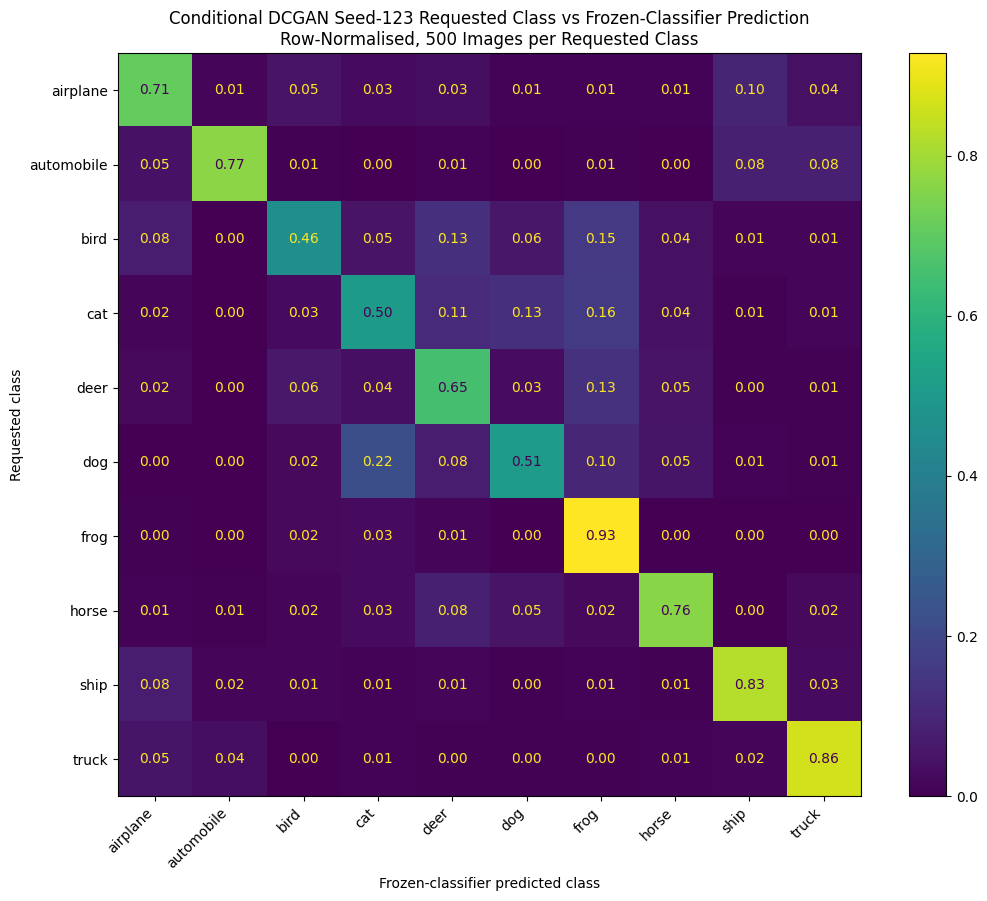

Classifier overall agreement: 0.6990
Mean requested-class probability: 0.6382
Normalised mutual information: 0.5318
Requested class is row maximum: 10 / 10
Represented predicted classes: 10
Dominant predicted-class share: 0.1522
Normalised predicted-class entropy: 0.9902
JS divergence from real predictions: 0.0043
Confusion figure saved: [local project directory]/grids/G11_conditional_fliptranslation_seed123_requested_vs_predicted_confusion.png
Classifier results remain supporting evidence rather than generated-image ground truth.
Protected test set remains unused.


In [94]:
conditional_seed123_confusion_counts_df = pd.DataFrame(
    conditional_seed123_requested_vs_predicted_counts,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

conditional_seed123_confusion_proportions_df = pd.DataFrame(
    conditional_seed123_requested_vs_predicted_proportions,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)


CONDITIONAL_SEED123_CONFUSION_COUNTS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "requested_vs_predicted_counts.csv"
    )
)

CONDITIONAL_SEED123_CONFUSION_PROPORTIONS_PATH = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "requested_vs_predicted_proportions.csv"
    )
)

CONDITIONAL_SEED123_CONFUSION_FIGURE_PATH = (
    GRIDS_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "requested_vs_predicted_confusion.png"
    )
)


conditional_seed123_confusion_counts_df.to_csv(
    CONDITIONAL_SEED123_CONFUSION_COUNTS_PATH,
    index=True,
)

conditional_seed123_confusion_proportions_df.to_csv(
    CONDITIONAL_SEED123_CONFUSION_PROPORTIONS_PATH,
    index=True,
)


figure, axis = plt.subplots(
    figsize=(11, 9)
)


confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=(
        conditional_seed123_requested_vs_predicted_proportions
    ),
    display_labels=CLASS_NAMES,
)


confusion_display.plot(
    ax=axis,
    values_format=".2f",
    colorbar=True,
)


axis.set_title(
    (
        "Conditional DCGAN Seed-123 Requested Class "
        "vs Frozen-Classifier Prediction\n"
        "Row-Normalised, 500 Images per Requested Class"
    )
)

axis.set_xlabel(
    "Frozen-classifier predicted class"
)

axis.set_ylabel(
    "Requested class"
)


plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    CONDITIONAL_SEED123_CONFUSION_FIGURE_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print(
    "Classifier overall agreement:",
    (
        f"{CONDITIONAL_SEED123_CLASSIFIER_OVERALL_AGREEMENT:.4f}"
    ),
)

print(
    "Mean requested-class probability:",
    (
        f"{CONDITIONAL_SEED123_CLASSIFIER_MEAN_REQUESTED_PROBABILITY:.4f}"
    ),
)

print(
    "Normalised mutual information:",
    (
        f"{CONDITIONAL_SEED123_CLASSIFIER_NMI:.4f}"
    ),
)

print(
    "Requested class is row maximum:",
    (
        f"{CONDITIONAL_SEED123_REQUESTED_ROW_MAXIMUM_COUNT}"
        f" / {NUM_CLASSES}"
    ),
)

print(
    "Represented predicted classes:",
    int(
        np.count_nonzero(
            conditional_seed123_predicted_counts
        )
    ),
)

print(
    "Dominant predicted-class share:",
    (
        f"{conditional_seed123_predicted_proportions.max():.4f}"
    ),
)

print(
    "Normalised predicted-class entropy:",
    (
        f"{CONDITIONAL_SEED123_PREDICTED_ENTROPY:.4f}"
    ),
)

print(
    "JS divergence from real predictions:",
    (
        f"{CONDITIONAL_SEED123_PREDICTED_JS_DIVERGENCE:.4f}"
    ),
)

print(
    "Confusion figure saved:",
    CONDITIONAL_SEED123_CONFUSION_FIGURE_PATH,
)

print(
    "Classifier results remain supporting "
    "evidence rather than generated-image ground truth."
)

print(
    "Protected test set remains unused."
)

### 13.20 Conditional Two-Seed Robustness Decision

The conditional DCGAN has now been trained and evaluated using two independent training seeds.

The selected checkpoints achieved:

| Training seed | Selected epoch | Repeated development FID |
|---:|---:|---:|
| 42 | 100 | `34.8933 ± 0.3457` |
| 123 | 100 | `35.2332 ± 0.1290` |

The absolute difference between the two repeated-FID means is `0.3399`, substantially below the predeclared practical margin of `2.0`. The two conditional training seeds are therefore treated as a practical FID tie.

Frozen-classifier adherence was also consistent:

| Metric | Seed 42 | Seed 123 |
|---|---:|---:|
| Overall requested-label agreement | `0.6890` | `0.6990` |
| Mean requested-class probability | `0.6302` | `0.6382` |
| Normalised mutual information | `0.5140` | `0.5318` |
| Requested class was row maximum | `10 / 10` | `10 / 10` |
| Represented predicted classes | `10 / 10` | `10 / 10` |

Both runs produced highly balanced predicted-class distributions, with normalised entropy above `0.99` and low Jensen-Shannon divergence from the held-out-real classifier prediction distribution.

The direct class-organised seed-123 grid also reproduced the principal seed-42 pattern. Vehicles and ships were generally clearer, while related animal classes showed greater visual ambiguity. No global label-ignoring, mode collapse or severe class-coverage failure was observed.

Seed `123` therefore confirms that the seed-42 conditional result was not dependent on one favourable initialisation.

No escalation to repeated manual scoring, descriptor analysis, diversity analysis or matched-noise analysis is required for seed `123`.

Seed `42` remains the representative conditional finalist because it received the complete evaluation package and achieved the slightly lower repeated FID. Seed `123` is retained as the independent robustness-confirmation run.

In [97]:
required_conditional_two_seed_objects = [
    "HISTORIES_DIR",
    "pd",
    "np",
]

missing_conditional_two_seed_objects = [
    name
    for name in required_conditional_two_seed_objects
    if name not in globals()
]

assert not missing_conditional_two_seed_objects, (
    "Incomplete conditional two-seed "
    "consolidation setup:\n"
    + "\n".join(
        missing_conditional_two_seed_objects
    )
)


CONDITIONAL_SEED42_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)

CONDITIONAL_SEED123_RUN_ID = (
    "G11_conditional_fliptranslation_seed123"
)


# Seed 42 used the earlier selected-checkpoint filename.
conditional_seed42_repeated_fid_path = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)

# Seed 123 used the newer filename.
conditional_seed123_repeated_fid_path = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "repeated_fid_summary.csv"
    )
)


conditional_seed42_classifier_path = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED42_RUN_ID}_"
        "classifier_adherence_summary.csv"
    )
)

conditional_seed123_classifier_path = (
    HISTORIES_DIR
    / (
        f"{CONDITIONAL_SEED123_RUN_ID}_"
        "classifier_adherence_summary.csv"
    )
)


conditional_two_seed_required_paths = [
    conditional_seed42_repeated_fid_path,
    conditional_seed123_repeated_fid_path,
    conditional_seed42_classifier_path,
    conditional_seed123_classifier_path,
]


for required_path in (
    conditional_two_seed_required_paths
):
    assert required_path.is_file(), (
        "Missing conditional robustness artifact:\n"
        f"{required_path}"
    )


print("Conditional robustness artifacts found:")

for required_path in (
    conditional_two_seed_required_paths
):
    print(required_path)


conditional_seed42_repeated_fid_df = pd.read_csv(
    conditional_seed42_repeated_fid_path
)

conditional_seed123_repeated_fid_df = pd.read_csv(
    conditional_seed123_repeated_fid_path
)

conditional_seed42_classifier_df = pd.read_csv(
    conditional_seed42_classifier_path
)

conditional_seed123_classifier_df = pd.read_csv(
    conditional_seed123_classifier_path
)


assert len(
    conditional_seed42_repeated_fid_df
) == 1

assert len(
    conditional_seed123_repeated_fid_df
) == 1

assert len(
    conditional_seed42_classifier_df
) == 1

assert len(
    conditional_seed123_classifier_df
) == 1


conditional_seed42_fid_row = (
    conditional_seed42_repeated_fid_df.iloc[0]
)

conditional_seed123_fid_row = (
    conditional_seed123_repeated_fid_df.iloc[0]
)

conditional_seed42_classifier_row = (
    conditional_seed42_classifier_df.iloc[0]
)

conditional_seed123_classifier_row = (
    conditional_seed123_classifier_df.iloc[0]
)


CONDITIONAL_SEED42_REPEATED_FID_MEAN = float(
    conditional_seed42_fid_row[
        "Repeated FID mean"
    ]
)

CONDITIONAL_SEED42_REPEATED_FID_SD = float(
    conditional_seed42_fid_row[
        "Repeated FID SD"
    ]
)

CONDITIONAL_SEED123_REPEATED_FID_MEAN = float(
    conditional_seed123_fid_row[
        "Repeated FID mean"
    ]
)

CONDITIONAL_SEED123_REPEATED_FID_SD = float(
    conditional_seed123_fid_row[
        "Repeated FID SD"
    ]
)


conditional_two_seed_fid_means = np.asarray(
    [
        CONDITIONAL_SEED42_REPEATED_FID_MEAN,
        CONDITIONAL_SEED123_REPEATED_FID_MEAN,
    ],
    dtype=np.float64,
)


CONDITIONAL_TWO_SEED_FID_MEAN = float(
    conditional_two_seed_fid_means.mean()
)

CONDITIONAL_TWO_SEED_FID_SD = float(
    conditional_two_seed_fid_means.std(
        ddof=1
    )
)

CONDITIONAL_TWO_SEED_FID_DIFFERENCE = float(
    np.abs(
        CONDITIONAL_SEED42_REPEATED_FID_MEAN
        - CONDITIONAL_SEED123_REPEATED_FID_MEAN
    )
)

CONDITIONAL_TWO_SEED_PRACTICAL_MARGIN = 2.0

CONDITIONAL_TWO_SEED_FID_PRACTICAL_TIE = bool(
    CONDITIONAL_TWO_SEED_FID_DIFFERENCE
    < CONDITIONAL_TWO_SEED_PRACTICAL_MARGIN
)


conditional_two_seed_summary_df = pd.DataFrame(
    [
        {
            "Training seed": 42,
            "Run ID": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Selected epoch": int(
                conditional_seed42_fid_row[
                    "Selected epoch"
                ]
            ),
            "Repeated FID mean": (
                CONDITIONAL_SEED42_REPEATED_FID_MEAN
            ),
            "Repeated FID SD": (
                CONDITIONAL_SEED42_REPEATED_FID_SD
            ),
            "Classifier agreement": float(
                conditional_seed42_classifier_row[
                    "Classifier overall agreement"
                ]
            ),
            "Mean requested-class probability": float(
                conditional_seed42_classifier_row[
                    "Mean requested-class probability"
                ]
            ),
            "Normalised mutual information": float(
                conditional_seed42_classifier_row[
                    "Normalised mutual information"
                ]
            ),
            "Requested-class row maxima": int(
                conditional_seed42_classifier_row[
                    "Requested classes where diagonal is row maximum"
                ]
            ),
            "Represented predicted classes": int(
                conditional_seed42_classifier_row[
                    "Represented predicted classes"
                ]
            ),
            "Normalised predicted-class entropy": float(
                conditional_seed42_classifier_row[
                    "Normalised predicted-class entropy"
                ]
            ),
            "JS divergence from real predictions": float(
                conditional_seed42_classifier_row[
                    "JS divergence from real predictions"
                ]
            ),
            "Role": (
                "Representative conditional finalist"
            ),
        },
        {
            "Training seed": 123,
            "Run ID": (
                CONDITIONAL_SEED123_RUN_ID
            ),
            "Selected epoch": int(
                conditional_seed123_fid_row[
                    "Selected epoch"
                ]
            ),
            "Repeated FID mean": (
                CONDITIONAL_SEED123_REPEATED_FID_MEAN
            ),
            "Repeated FID SD": (
                CONDITIONAL_SEED123_REPEATED_FID_SD
            ),
            "Classifier agreement": float(
                conditional_seed123_classifier_row[
                    "Classifier overall agreement"
                ]
            ),
            "Mean requested-class probability": float(
                conditional_seed123_classifier_row[
                    "Mean requested-class probability"
                ]
            ),
            "Normalised mutual information": float(
                conditional_seed123_classifier_row[
                    "Normalised mutual information"
                ]
            ),
            "Requested-class row maxima": int(
                conditional_seed123_classifier_row[
                    "Requested classes where diagonal is row maximum"
                ]
            ),
            "Represented predicted classes": int(
                conditional_seed123_classifier_row[
                    "Represented predicted classes"
                ]
            ),
            "Normalised predicted-class entropy": float(
                conditional_seed123_classifier_row[
                    "Normalised predicted-class entropy"
                ]
            ),
            "JS divergence from real predictions": float(
                conditional_seed123_classifier_row[
                    "JS divergence from real predictions"
                ]
            ),
            "Role": (
                "Independent robustness confirmation"
            ),
        },
    ]
)


assert (
    conditional_two_seed_summary_df[
        "Requested-class row maxima"
    ]
    == 10
).all()

assert (
    conditional_two_seed_summary_df[
        "Represented predicted classes"
    ]
    == 10
).all()


conditional_two_seed_decision_df = pd.DataFrame(
    [
        {
            "Conditional training seeds": (
                "(42, 123)"
            ),
            "Mean of training-seed FID means": (
                CONDITIONAL_TWO_SEED_FID_MEAN
            ),
            "SD of training-seed FID means": (
                CONDITIONAL_TWO_SEED_FID_SD
            ),
            "Absolute FID difference": (
                CONDITIONAL_TWO_SEED_FID_DIFFERENCE
            ),
            "Practical FID margin": (
                CONDITIONAL_TWO_SEED_PRACTICAL_MARGIN
            ),
            "Practical FID tie": (
                CONDITIONAL_TWO_SEED_FID_PRACTICAL_TIE
            ),
            "Both runs have 10 row maxima": True,
            "Both runs represent all 10 classes": True,
            "Seed-123 escalation required": False,
            "Representative conditional run": (
                CONDITIONAL_SEED42_RUN_ID
            ),
            "Decision": (
                "Seed 123 confirms the seed-42 "
                "conditional result. No repeated "
                "manual, descriptor, diversity or "
                "matched-noise escalation is required."
            ),
        }
    ]
)


assert CONDITIONAL_TWO_SEED_FID_PRACTICAL_TIE


CONDITIONAL_TWO_SEED_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        "conditional_two_seed_"
        "robustness_summary.csv"
    )
)

CONDITIONAL_TWO_SEED_DECISION_PATH = (
    HISTORIES_DIR
    / (
        "conditional_two_seed_"
        "robustness_decision.csv"
    )
)


conditional_two_seed_summary_df.to_csv(
    CONDITIONAL_TWO_SEED_SUMMARY_PATH,
    index=False,
)

conditional_two_seed_decision_df.to_csv(
    CONDITIONAL_TWO_SEED_DECISION_PATH,
    index=False,
)


display(
    conditional_two_seed_summary_df.round(4)
)

display(
    conditional_two_seed_decision_df.round(4)
)


print(
    "Two-seed conditional FID mean:",
    f"{CONDITIONAL_TWO_SEED_FID_MEAN:.4f}",
)

print(
    "Training-seed FID SD:",
    f"{CONDITIONAL_TWO_SEED_FID_SD:.4f}",
)

print(
    "Absolute training-seed FID difference:",
    f"{CONDITIONAL_TWO_SEED_FID_DIFFERENCE:.4f}",
)

print(
    "Practical FID tie:",
    CONDITIONAL_TWO_SEED_FID_PRACTICAL_TIE,
)

print(
    "Representative conditional run:",
    CONDITIONAL_SEED42_RUN_ID,
)

print(
    "Seed-123 escalation required:",
    False,
)

print(
    "Conditional two-seed robustness "
    "package is closed."
)

print(
    "Protected test set remains unused."
)

Conditional robustness artifacts found:
[local project directory]/histories/G10_conditional_fliptranslation_seed42_selected_repeated_fid_summary.csv
[local project directory]/histories/G11_conditional_fliptranslation_seed123_repeated_fid_summary.csv
[local project directory]/histories/G10_conditional_fliptranslation_seed42_classifier_adherence_summary.csv
[local project directory]/histories/G11_conditional_fliptranslation_seed123_classifier_adherence_summary.csv


,Training seed,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD,Classifier agreement,Mean requested-class probability,Normalised mutual information,Requested-class row maxima,Represented predicted classes,Normalised predicted-class entropy,JS divergence from real predictions,Role
0,42,G10_conditional_fliptranslation_seed42,100,34.8933,0.3457,0.689,0.6302,0.5140,10,10,0.9910,0.0039,Representative conditional finalist
1,123,G11_conditional_fliptranslation_seed123,100,35.2332,0.1290,0.699,0.6382,0.5318,10,10,0.9902,0.0043,Independent robustness confirmation


,Conditional training seeds,Mean of training-seed FID means,SD of training-seed FID means,Absolute FID difference,Practical FID margin,Practical FID tie,Both runs have 10 row maxima,Both runs represent all 10 classes,Seed-123 escalation required,Representative conditional run,Decision
0,"(42, 123)",35.0633,0.2403,0.3399,2.0,True,True,True,False,G10_conditional_fliptranslation_seed42,Seed 123 confirms the seed-42 conditional resu...


Two-seed conditional FID mean: 35.0633
Training-seed FID SD: 0.2403
Absolute training-seed FID difference: 0.3399
Practical FID tie: True
Representative conditional run: G10_conditional_fliptranslation_seed42
Seed-123 escalation required: False
Conditional two-seed robustness package is closed.
Protected test set remains unused.


## 14. Discussion-Only: Grayscale Sensitivity Experiment

This section investigates whether removing colour information simplifies CIFAR-10 generation enough to improve object structure.

The scientific question is:

> Does reducing CIFAR-10 from three colour channels to one grayscale channel improve structural generation enough to compensate for losing useful colour information?

This experiment is **discussion-focused only**.

It is not part of the final GAN competition and cannot replace either the selected RGB unconditional GAN or the conditional GAN. Even if the grayscale model achieves a favourable grayscale-reference FID or manual recognisability score, it will not be considered for final-model selection because it cannot generate normal RGB CIFAR-10 images.

Checkpoint selection within this section only identifies the most representative grayscale checkpoint for answering the scientific question.

The experiment uses:

- all `50,000` CIFAR-10 training images;
- luminance-based RGB-to-grayscale conversion;
- input and output shape `32 × 32 × 1`;
- the retained unconditional DCGAN architecture adapted only for one channel;
- horizontal flipping and two-pixel translation;
- training seed `42`;
- latent dimension `100`;
- batch size `64`;
- equal generator and discriminator learning rates of `2 × 10⁻⁴`;
- Adam with `beta_1 = 0.5` and `beta_2 = 0.999`;
- one discriminator update followed by one generator update per batch;
- `100` epochs;
- milestone weights at epochs `50`, `70`, `90` and `100`.

There is no grayscale hyperparameter sweep, architecture sweep or second grayscale training seed.

A fair grayscale FID reference will later be calculated from all `50,000` grayscale-transformed training images. Grayscale real and generated images will be replicated to three channels only when passed through InceptionV3.

The normal RGB FID reference will not be used as the primary grayscale reference.

The protected CIFAR-10 test set remains unused.

In [51]:
required_grayscale_contract_objects = [
    "PRIMARY_SEED",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "FORMAL_MILESTONE_EPOCHS",
    "FIXED_PROGRESSION_SEED",
    "x_train_gan",
    "y_train",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "tf",
    "np",
    "pd",
]

missing_grayscale_contract_objects = [
    name
    for name in required_grayscale_contract_objects
    if name not in globals()
]

assert not missing_grayscale_contract_objects, (
    "Incomplete grayscale experiment setup:\n"
    + "\n".join(
        missing_grayscale_contract_objects
    )
)


GRAYSCALE_RUN_ID = (
    "G12_grayscale_fliptranslation_seed42"
)

GRAYSCALE_MODEL_LABEL = (
    "Discussion-Only Grayscale DCGAN, "
    "Flip + Translation, Seed 42"
)

GRAYSCALE_EXPERIMENT_ROLE = (
    "discussion_only"
)

GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION = False

GRAYSCALE_RESEARCH_QUESTION = (
    "Does reducing channel complexity improve "
    "structural generation enough to compensate "
    "for losing useful CIFAR-10 colour information?"
)

GRAYSCALE_TRAINING_SEED = PRIMARY_SEED

GRAYSCALE_AUGMENTATION_SEED = (
    GRAYSCALE_TRAINING_SEED
)

GRAYSCALE_TRANSLATION_SEED = (
    GRAYSCALE_AUGMENTATION_SEED + 1
)

GRAYSCALE_IMAGE_SHAPE = (
    32,
    32,
    1,
)

GRAYSCALE_CHANNELS = 1

GRAYSCALE_LATENT_DIM = (
    CURRENT_LATENT_DIM
)

GRAYSCALE_BATCH_SIZE = (
    CURRENT_BATCH_SIZE
)

GRAYSCALE_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

GRAYSCALE_GENERATOR_LR = (
    CURRENT_GENERATOR_LR
)

GRAYSCALE_DISCRIMINATOR_LR = (
    CURRENT_DISCRIMINATOR_LR
)

GRAYSCALE_BETA_1 = (
    CURRENT_BETA_1
)

GRAYSCALE_BETA_2 = (
    CURRENT_BETA_2
)

GRAYSCALE_UPDATE_RATIO = (
    CURRENT_UPDATE_RATIO
)

GRAYSCALE_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

GRAYSCALE_CHECKPOINT_INTERVAL = 10

GRAYSCALE_FIXED_GRID_SIZE = 25

GRAYSCALE_FIXED_GRID_SEED = (
    FIXED_PROGRESSION_SEED
)

GRAYSCALE_BATCHES_PER_EPOCH = int(
    np.ceil(
        len(x_train_gan)
        / GRAYSCALE_BATCH_SIZE
    )
)

GRAYSCALE_EXPECTED_UPDATES = int(
    GRAYSCALE_BATCHES_PER_EPOCH
    * GRAYSCALE_TARGET_EPOCHS
)


assert GRAYSCALE_EXPERIMENT_ROLE == (
    "discussion_only"
)

assert (
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
    is False
)

assert GRAYSCALE_TRAINING_SEED == 42
assert GRAYSCALE_AUGMENTATION_SEED == 42
assert GRAYSCALE_TRANSLATION_SEED == 43

assert GRAYSCALE_LATENT_DIM == 100
assert GRAYSCALE_BATCH_SIZE == 64
assert GRAYSCALE_TARGET_EPOCHS == 100

assert GRAYSCALE_GENERATOR_LR == 2e-4
assert GRAYSCALE_DISCRIMINATOR_LR == 2e-4

assert GRAYSCALE_BETA_1 == 0.5
assert GRAYSCALE_BETA_2 == 0.999

assert GRAYSCALE_UPDATE_RATIO == "1D:1G"

assert (
    GRAYSCALE_MILESTONE_EPOCHS
    == (50, 70, 90, 100)
)

assert GRAYSCALE_BATCHES_PER_EPOCH == 782
assert GRAYSCALE_EXPECTED_UPDATES == 78_200


x_train_grayscale_gan = (
    tf.image.rgb_to_grayscale(
        tf.convert_to_tensor(
            x_train_gan,
            dtype=tf.float32,
        )
    )
    .numpy()
    .astype(np.float32)
)


assert x_train_grayscale_gan.shape == (
    50_000,
    32,
    32,
    1,
)

assert x_train_grayscale_gan.dtype == np.float32

assert np.isfinite(
    x_train_grayscale_gan
).all()

assert float(
    x_train_grayscale_gan.min()
) >= -1.0

assert float(
    x_train_grayscale_gan.max()
) <= 1.0

assert y_train.shape == (
    50_000,
)


grayscale_contract_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Experiment role": (
                GRAYSCALE_EXPERIMENT_ROLE
            ),
            "Eligible for final GAN selection": (
                GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
            ),
            "Training seed": (
                GRAYSCALE_TRAINING_SEED
            ),
            "Training shape": str(
                x_train_grayscale_gan.shape
            ),
            "Latent dimension": (
                GRAYSCALE_LATENT_DIM
            ),
            "Batch size": (
                GRAYSCALE_BATCH_SIZE
            ),
            "Epochs": (
                GRAYSCALE_TARGET_EPOCHS
            ),
            "Generator LR": (
                GRAYSCALE_GENERATOR_LR
            ),
            "Discriminator LR": (
                GRAYSCALE_DISCRIMINATOR_LR
            ),
            "Augmentation": (
                "Horizontal flip + "
                "two-pixel translation"
            ),
            "Milestone epochs": str(
                GRAYSCALE_MILESTONE_EPOCHS
            ),
            "Expected updates per network": (
                GRAYSCALE_EXPECTED_UPDATES
            ),
        }
    ]
)


display(
    grayscale_contract_df
)


print(
    "Grayscale training range:",
    (
        f"[{x_train_grayscale_gan.min():.4f}, "
        f"{x_train_grayscale_gan.max():.4f}]"
    ),
)

print(
    "Experiment role:",
    GRAYSCALE_EXPERIMENT_ROLE,
)

print(
    "Eligible for final GAN selection:",
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION,
)

print(
    "Research question:",
    GRAYSCALE_RESEARCH_QUESTION,
)

print("Protected test set remains unused.")

,Run ID,Experiment role,Eligible for final GAN selection,Training seed,Training shape,Latent dimension,Batch size,Epochs,Generator LR,Discriminator LR,Augmentation,Milestone epochs,Expected updates per network
0,G12_grayscale_fliptranslation_seed42,discussion_only,False,42,"(50000, 32, 32, 1)",100,64,100,0.0002,0.0002,Horizontal flip + two-pixel translation,"(50, 70, 90, 100)",78200


Grayscale training range: [-0.9999, 0.9999]
Experiment role: discussion_only
Eligible for final GAN selection: False
Research question: Does reducing channel complexity improve structural generation enough to compensate for losing useful CIFAR-10 colour information?
Protected test set remains unused.


### 14.1 Grayscale Architecture Adaptation

The retained RGB DCGAN architecture is adapted only where the channel count requires it.

The grayscale generator keeps the same latent projection, spatial resolutions, convolutional widths, Batch Normalisation layers, LeakyReLU activations and transposed-convolution upsampling stages. Its final layer produces one `tanh`-scaled channel instead of three.

The grayscale discriminator keeps the same convolutional widths, spatial reductions, Batch Normalisation layers, LeakyReLU activations and sigmoid output. Its input shape changes from `32 × 32 × 3` to `32 × 32 × 1`.

The flip-and-translation augmentation policy remains inside the discriminator, so independently sampled transformations are applied symmetrically when the discriminator processes real and generated images.

These channel adaptations are necessary for the grayscale question. They are not a new architecture family or capacity experiment.

In [52]:
required_grayscale_architecture_objects = [
    "keras",
    "layers",
    "initializers",
    "build_dcgan_augmentation_policy",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_AUGMENTATION_SEED",
    "GRAYSCALE_IMAGE_SHAPE",
    "GRAYSCALE_FIXED_GRID_SIZE",
    "CLASS_NAMES",
    "Path",
    "np",
    "plt",
]

missing_grayscale_architecture_objects = [
    name
    for name in required_grayscale_architecture_objects
    if name not in globals()
]

assert not missing_grayscale_architecture_objects, (
    "Incomplete grayscale architecture setup:\n"
    + "\n".join(
        missing_grayscale_architecture_objects
    )
)


def build_grayscale_dcgan_generator(
    latent_dim,
):
    latent_dim = int(
        latent_dim
    )

    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=(latent_dim,)
            ),

            layers.Dense(
                4 * 4 * 256,
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Reshape(
                (4, 4, 256)
            ),

            layers.Conv2DTranspose(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2DTranspose(
                1,
                kernel_size=4,
                strides=2,
                padding="same",
                activation="tanh",
                kernel_initializer=weight_init,
            ),
        ],
        name="Grayscale_DCGAN_Generator",
    )

    return model


def build_grayscale_dcgan_discriminator():
    weight_init = initializers.RandomNormal(
        mean=0.0,
        stddev=0.02,
    )

    model = keras.Sequential(
        [
            layers.Input(
                shape=GRAYSCALE_IMAGE_SHAPE
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same",
                kernel_initializer=weight_init,
            ),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same",
                use_bias=False,
                kernel_initializer=weight_init,
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(
                negative_slope=0.2
            ),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                kernel_initializer=weight_init,
            ),
        ],
        name="Grayscale_DCGAN_Discriminator",
    )

    return model


def build_grayscale_augmented_discriminator():
    augmentation_policy = (
        build_dcgan_augmentation_policy(
            policy_name="flip_translation",
            augmentation_seed=(
                GRAYSCALE_AUGMENTATION_SEED
            ),
        )
    )

    base_discriminator = (
        build_grayscale_dcgan_discriminator()
    )

    discriminator_input = layers.Input(
        shape=GRAYSCALE_IMAGE_SHAPE,
        name="grayscale_augmented_input",
    )

    augmented_input = augmentation_policy(
        discriminator_input
    )

    discriminator_output = (
        base_discriminator(
            augmented_input
        )
    )

    return keras.Model(
        inputs=discriminator_input,
        outputs=discriminator_output,
        name=(
            "Grayscale_DCGAN_"
            "FlipTranslation_Discriminator"
        ),
    )


def save_grayscale_generated_grid(
    generator,
    noise,
    save_path,
    title,
):
    generated_images = generator(
        noise,
        training=False,
    ).numpy()

    generated_images = np.clip(
        (
            generated_images + 1.0
        )
        / 2.0,
        0.0,
        1.0,
    )

    assert generated_images.shape == (
        GRAYSCALE_FIXED_GRID_SIZE,
        32,
        32,
        1,
    )

    figure, axes = plt.subplots(
        5,
        5,
        figsize=(7, 7),
    )

    for index, axis in enumerate(
        axes.flat
    ):
        axis.imshow(
            generated_images[
                index,
                :,
                :,
                0,
            ],
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        axis.axis("off")

    figure.suptitle(
        title,
        fontsize=13,
    )

    figure.tight_layout()

    save_path = Path(
        save_path
    )

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    figure.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )

    return save_path


grayscale_architecture_probe_generator = (
    build_grayscale_dcgan_generator(
        GRAYSCALE_LATENT_DIM
    )
)

grayscale_architecture_probe_discriminator = (
    build_grayscale_augmented_discriminator()
)


GRAYSCALE_GENERATOR_PARAMETERS = int(
    grayscale_architecture_probe_generator.count_params()
)

GRAYSCALE_DISCRIMINATOR_PARAMETERS = int(
    grayscale_architecture_probe_discriminator.count_params()
)


assert (
    grayscale_architecture_probe_generator.output_shape
    == (
        None,
        32,
        32,
        1,
    )
)

assert (
    grayscale_architecture_probe_discriminator.input_shape
    == (
        None,
        32,
        32,
        1,
    )
)

assert (
    grayscale_architecture_probe_discriminator.output_shape
    == (
        None,
        1,
    )
)

assert GRAYSCALE_GENERATOR_PARAMETERS == 1_083_137

assert GRAYSCALE_DISCRIMINATOR_PARAMETERS == 662_081


grayscale_architecture_df = pd.DataFrame(
    [
        {
            "Network": "Generator",
            "Input shape": (
                str(
                    grayscale_architecture_probe_generator
                    .input_shape
                )
            ),
            "Output shape": (
                str(
                    grayscale_architecture_probe_generator
                    .output_shape
                )
            ),
            "Parameters": (
                GRAYSCALE_GENERATOR_PARAMETERS
            ),
        },
        {
            "Network": "Discriminator",
            "Input shape": (
                str(
                    grayscale_architecture_probe_discriminator
                    .input_shape
                )
            ),
            "Output shape": (
                str(
                    grayscale_architecture_probe_discriminator
                    .output_shape
                )
            ),
            "Parameters": (
                GRAYSCALE_DISCRIMINATOR_PARAMETERS
            ),
        },
    ]
)


display(
    grayscale_architecture_df
)


print(
    "Grayscale architecture validated."
)

print(
    "Generator output channels:",
    grayscale_architecture_probe_generator
    .output_shape[-1],
)

print(
    "Discriminator input channels:",
    grayscale_architecture_probe_discriminator
    .input_shape[-1],
)

print(
    "This is a channel adaptation, "
    "not a new capacity experiment."
)

print("Protected test set remains unused.")


del grayscale_architecture_probe_generator
del grayscale_architecture_probe_discriminator

keras.backend.clear_session()

,Network,Input shape,Output shape,Parameters
0,Generator,"(None, 100)","(None, 32, 32, 1)",1083137
1,Discriminator,"(None, 32, 32, 1)","(None, 1)",662081


Grayscale architecture validated.
Generator output channels: 1
Discriminator input channels: 1
This is a channel adaptation, not a new capacity experiment.
Protected test set remains unused.


### 14.2 Restart-Safe Grayscale Training

The grayscale run follows the same alternating update procedure as the retained unconditional DCGAN.

For each batch:

1. the discriminator is updated once using grayscale real images and detached grayscale generated images;
2. the generator is updated once using a fresh latent sample;
3. the same binary cross-entropy objective and Adam settings are retained.

The shared unconditional training step, optimiser, history, checkpoint and milestone utilities are reused unchanged.

A grayscale-specific orchestration is necessary only because the earlier reusable trainer validates RGB shape `32 × 32 × 3` and its grid helper displays RGB images.

Checkpoints and grayscale grids are saved every ten epochs. Generator and discriminator milestone weights are saved at epochs `50`, `70`, `90` and `100`.

This training run does not make the grayscale model eligible for final GAN selection.

In [102]:
required_grayscale_training_objects = [
    "keras",
    "tf",
    "np",
    "pd",
    "time",
    "Path",
    "x_train_grayscale_gan",
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_TRAINING_SEED",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_BATCH_SIZE",
    "GRAYSCALE_TARGET_EPOCHS",
    "GRAYSCALE_GENERATOR_LR",
    "GRAYSCALE_DISCRIMINATOR_LR",
    "GRAYSCALE_BETA_1",
    "GRAYSCALE_BETA_2",
    "GRAYSCALE_MILESTONE_EPOCHS",
    "GRAYSCALE_CHECKPOINT_INTERVAL",
    "GRAYSCALE_FIXED_GRID_SIZE",
    "GRAYSCALE_FIXED_GRID_SEED",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "reset_run_seed",
    "make_training_dataset",
    "build_grayscale_dcgan_generator",
    "build_grayscale_augmented_discriminator",
    "build_dcgan_training_components",
    "build_dcgan_checkpoint_objects",
    "create_dcgan_checkpoint_manager",
    "restore_dcgan_run_state",
    "make_dcgan_train_step",
    "make_stateless_noise",
    "save_dcgan_epoch_history",
    "save_dcgan_milestone_weights",
    "save_grayscale_generated_grid",
    "inspect_dcgan_training_status",
    "assert_fresh_run_construction_order",
]

missing_grayscale_training_objects = [
    name
    for name in required_grayscale_training_objects
    if name not in globals()
]

assert not missing_grayscale_training_objects, (
    "Incomplete grayscale training setup:\n"
    + "\n".join(
        missing_grayscale_training_objects
    )
)


GRAYSCALE_CHECKPOINT_DIR = (
    Path(CHECKPOINTS_DIR)
    / GRAYSCALE_RUN_ID
)

GRAYSCALE_HISTORY_PATH = (
    Path(HISTORIES_DIR)
    / f"{GRAYSCALE_RUN_ID}.csv"
)


grayscale_status_before = (
    inspect_dcgan_training_status(
        run_id=GRAYSCALE_RUN_ID,
        target_epochs=(
            GRAYSCALE_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            GRAYSCALE_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            GRAYSCALE_CHECKPOINT_INTERVAL
        ),
    )
)


GRAYSCALE_SHOULD_TRAIN = (
    grayscale_status_before[
        "status"
    ]
    != "completed"
)


if not GRAYSCALE_SHOULD_TRAIN:
    grayscale_history_df = pd.read_csv(
        GRAYSCALE_HISTORY_PATH
    )

    grayscale_restored_epoch = (
        GRAYSCALE_TARGET_EPOCHS
    )

    grayscale_run_action = "skipped"

    print(
        f"{GRAYSCALE_RUN_ID} is already complete."
    )

    print(
        "Existing artifacts will be reused."
    )

else:
    grayscale_construction_trace = []

    keras.backend.clear_session()

    grayscale_construction_trace.append(
        "clear_keras_session"
    )

    reset_run_seed(
        GRAYSCALE_TRAINING_SEED
    )

    grayscale_construction_trace.append(
        "reset_complete_run_seed"
    )


    grayscale_generator = (
        build_grayscale_dcgan_generator(
            GRAYSCALE_LATENT_DIM
        )
    )

    grayscale_discriminator = (
        build_grayscale_augmented_discriminator()
    )

    grayscale_construction_trace.append(
        "build_fresh_models"
    )


    assert int(
        grayscale_generator.count_params()
    ) == GRAYSCALE_GENERATOR_PARAMETERS

    assert int(
        grayscale_discriminator.count_params()
    ) == GRAYSCALE_DISCRIMINATOR_PARAMETERS


    (
        grayscale_adversarial_loss,
        grayscale_generator_optimizer,
        grayscale_discriminator_optimizer,
    ) = build_dcgan_training_components(
        generator=grayscale_generator,
        discriminator=grayscale_discriminator,
        generator_learning_rate=(
            GRAYSCALE_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            GRAYSCALE_DISCRIMINATOR_LR
        ),
        beta_1=GRAYSCALE_BETA_1,
        beta_2=GRAYSCALE_BETA_2,
    )

    grayscale_construction_trace.append(
        "build_fresh_optimisers"
    )


    grayscale_training_dataset = (
        make_training_dataset(
            images=x_train_grayscale_gan,
            batch_size=GRAYSCALE_BATCH_SIZE,
            seed=GRAYSCALE_TRAINING_SEED,
        )
    )

    grayscale_construction_trace.append(
        "build_seeded_dataset"
    )


    (
        grayscale_completed_epoch,
        grayscale_checkpoint,
    ) = build_dcgan_checkpoint_objects(
        generator=grayscale_generator,
        discriminator=grayscale_discriminator,
        generator_optimizer=(
            grayscale_generator_optimizer
        ),
        discriminator_optimizer=(
            grayscale_discriminator_optimizer
        ),
    )

    grayscale_construction_trace.append(
        "create_checkpoint_objects"
    )


    assert_fresh_run_construction_order(
        grayscale_construction_trace
    )


    grayscale_checkpoint_manager = (
        create_dcgan_checkpoint_manager(
            checkpoint=grayscale_checkpoint,
            checkpoint_dir=(
                GRAYSCALE_CHECKPOINT_DIR
            ),
            max_to_keep=3,
        )
    )


    (
        grayscale_history_df,
        grayscale_restored_checkpoint,
    ) = restore_dcgan_run_state(
        checkpoint=grayscale_checkpoint,
        checkpoint_manager=(
            grayscale_checkpoint_manager
        ),
        completed_epoch=(
            grayscale_completed_epoch
        ),
        history_path=(
            GRAYSCALE_HISTORY_PATH
        ),
    )


    grayscale_restored_epoch = int(
        grayscale_completed_epoch.numpy()
    )


    assert (
        grayscale_restored_epoch
        == grayscale_status_before[
            "checkpoint_epoch"
        ]
    )


    grayscale_train_step = (
        make_dcgan_train_step(
            generator=grayscale_generator,
            discriminator=grayscale_discriminator,
            adversarial_loss=(
                grayscale_adversarial_loss
            ),
            generator_optimizer=(
                grayscale_generator_optimizer
            ),
            discriminator_optimizer=(
                grayscale_discriminator_optimizer
            ),
            latent_dim=GRAYSCALE_LATENT_DIM,
        )
    )


    grayscale_fixed_noise = (
        make_stateless_noise(
            sample_count=(
                GRAYSCALE_FIXED_GRID_SIZE
            ),
            latent_dim=(
                GRAYSCALE_LATENT_DIM
            ),
            seed=(
                GRAYSCALE_FIXED_GRID_SEED
            ),
        )
    )


    observed_grayscale_batches = int(
        tf.data.experimental.cardinality(
            grayscale_training_dataset
        ).numpy()
    )


    assert (
        observed_grayscale_batches
        == GRAYSCALE_BATCHES_PER_EPOCH
    )


    if grayscale_restored_epoch == 0:
        grayscale_run_action = "trained_new"

        print(
            f"Training new grayscale run "
            f"{GRAYSCALE_RUN_ID} from "
            "epoch 1 to "
            f"{GRAYSCALE_TARGET_EPOCHS}."
        )

    else:
        grayscale_run_action = "resumed"

        print(
            f"Resuming {GRAYSCALE_RUN_ID} "
            f"from epoch "
            f"{grayscale_restored_epoch + 1} "
            f"to {GRAYSCALE_TARGET_EPOCHS}."
        )

        print(
            "Restored checkpoint:",
            grayscale_restored_checkpoint,
        )


print(
    "Status before training:",
    grayscale_status_before[
        "status"
    ],
)

print(
    "Restored epoch:",
    grayscale_restored_epoch,
)

print(
    "Training required:",
    GRAYSCALE_SHOULD_TRAIN,
)

print(
    "Eligible for final GAN selection:",
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION,
)

print("Protected test set remains unused.")

Training new grayscale run G12_grayscale_fliptranslation_seed42 from epoch 1 to 100.
Status before training: new
Restored epoch: 0
Training required: True
Eligible for final GAN selection: False
Protected test set remains unused.


In [103]:
if GRAYSCALE_SHOULD_TRAIN:
    grayscale_start_epoch = (
        grayscale_restored_epoch + 1
    )

    grayscale_failed_epoch = None

    try:
        for epoch in range(
            grayscale_start_epoch,
            GRAYSCALE_TARGET_EPOCHS + 1,
        ):
            grayscale_failed_epoch = epoch

            epoch_start_time = time.time()

            generator_loss_mean = (
                keras.metrics.Mean()
            )

            discriminator_loss_mean = (
                keras.metrics.Mean()
            )

            real_score_mean = (
                keras.metrics.Mean()
            )

            fake_score_mean = (
                keras.metrics.Mean()
            )


            for real_images in (
                grayscale_training_dataset
            ):
                batch_results = (
                    grayscale_train_step(
                        real_images
                    )
                )

                generator_loss_mean.update_state(
                    batch_results[
                        "generator_loss"
                    ]
                )

                discriminator_loss_mean.update_state(
                    batch_results[
                        "discriminator_loss"
                    ]
                )

                real_score_mean.update_state(
                    batch_results[
                        "real_score"
                    ]
                )

                fake_score_mean.update_state(
                    batch_results[
                        "fake_score"
                    ]
                )


            epoch_time_seconds = float(
                time.time()
                - epoch_start_time
            )


            epoch_results = {
                "epoch": epoch,
                "generator_loss": float(
                    generator_loss_mean
                    .result()
                    .numpy()
                ),
                "discriminator_loss": float(
                    discriminator_loss_mean
                    .result()
                    .numpy()
                ),
                "real_score": float(
                    real_score_mean
                    .result()
                    .numpy()
                ),
                "fake_score": float(
                    fake_score_mean
                    .result()
                    .numpy()
                ),
                "epoch_time_seconds": (
                    epoch_time_seconds
                ),
            }


            numeric_epoch_results = np.asarray(
                [
                    epoch_results[
                        "generator_loss"
                    ],
                    epoch_results[
                        "discriminator_loss"
                    ],
                    epoch_results[
                        "real_score"
                    ],
                    epoch_results[
                        "fake_score"
                    ],
                    epoch_results[
                        "epoch_time_seconds"
                    ],
                ],
                dtype=np.float64,
            )


            if not np.isfinite(
                numeric_epoch_results
            ).all():
                raise FloatingPointError(
                    "Non-finite grayscale "
                    "training value detected at "
                    f"epoch {epoch}."
                )


            grayscale_completed_epoch.assign(
                epoch
            )


            grayscale_history_df = (
                save_dcgan_epoch_history(
                    history_path=(
                        GRAYSCALE_HISTORY_PATH
                    ),
                    epoch_results=(
                        epoch_results
                    ),
                )
            )


            if (
                epoch
                in GRAYSCALE_MILESTONE_EPOCHS
            ):
                (
                    milestone_generator_path,
                    milestone_discriminator_path,
                ) = save_dcgan_milestone_weights(
                    generator=(
                        grayscale_generator
                    ),
                    discriminator=(
                        grayscale_discriminator
                    ),
                    run_id=GRAYSCALE_RUN_ID,
                    epoch=epoch,
                    weights_dir=WEIGHTS_DIR,
                )

                print(
                    "Saved milestone generator:",
                    milestone_generator_path,
                )

                print(
                    "Saved milestone discriminator:",
                    milestone_discriminator_path,
                )


            save_progress_state = (
                epoch
                % GRAYSCALE_CHECKPOINT_INTERVAL
                == 0
            ) or (
                epoch
                == GRAYSCALE_TARGET_EPOCHS
            )


            if save_progress_state:
                checkpoint_path = (
                    grayscale_checkpoint_manager
                    .save(
                        checkpoint_number=epoch
                    )
                )

                grid_path = (
                    Path(GRIDS_DIR)
                    / (
                        f"{GRAYSCALE_RUN_ID}_"
                        f"epoch{epoch:03d}.png"
                    )
                )

                save_grayscale_generated_grid(
                    generator=(
                        grayscale_generator
                    ),
                    noise=(
                        grayscale_fixed_noise
                    ),
                    save_path=grid_path,
                    title=(
                        "Discussion-Only "
                        "Grayscale DCGAN, "
                        f"Epoch {epoch}"
                    ),
                )

                print(
                    "Saved checkpoint:",
                    checkpoint_path,
                )

                print(
                    "Saved grayscale grid:",
                    grid_path,
                )


            print(
                f"Epoch {epoch:03d}/"
                f"{GRAYSCALE_TARGET_EPOCHS} "
                f"| G loss: "
                f"{epoch_results['generator_loss']:.4f} "
                f"| D loss: "
                f"{epoch_results['discriminator_loss']:.4f} "
                f"| Real: "
                f"{epoch_results['real_score']:.4f} "
                f"| Fake: "
                f"{epoch_results['fake_score']:.4f} "
                f"| Time: "
                f"{epoch_time_seconds:.1f}s"
            )


    except Exception:
        print(
            "\nGrayscale training failed "
            "during epoch "
            f"{grayscale_failed_epoch}."
        )

        print(
            "Latest recoverable checkpoint:",
            (
                grayscale_checkpoint_manager
                .latest_checkpoint
            ),
        )

        print(
            "The exception is being re-raised."
        )

        raise


grayscale_final_status = (
    inspect_dcgan_training_status(
        run_id=GRAYSCALE_RUN_ID,
        target_epochs=(
            GRAYSCALE_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            GRAYSCALE_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            GRAYSCALE_CHECKPOINT_INTERVAL
        ),
    )
)


assert (
    grayscale_final_status[
        "status"
    ]
    == "completed"
)


grayscale_history_df = pd.read_csv(
    GRAYSCALE_HISTORY_PATH
)


GRAYSCALE_TRAINING_TIME_MINUTES = float(
    grayscale_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


if GRAYSCALE_SHOULD_TRAIN:
    grayscale_generator_updates = int(
        grayscale_generator_optimizer
        .iterations
        .numpy()
    )

    grayscale_discriminator_updates = int(
        grayscale_discriminator_optimizer
        .iterations
        .numpy()
    )

else:
    grayscale_generator_updates = (
        GRAYSCALE_EXPECTED_UPDATES
    )

    grayscale_discriminator_updates = (
        GRAYSCALE_EXPECTED_UPDATES
    )


assert (
    grayscale_generator_updates
    == GRAYSCALE_EXPECTED_UPDATES
)

assert (
    grayscale_discriminator_updates
    == GRAYSCALE_EXPECTED_UPDATES
)


grayscale_training_summary_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Action": grayscale_run_action,
            "Restored epoch": (
                grayscale_restored_epoch
            ),
            "Epochs completed": (
                GRAYSCALE_TARGET_EPOCHS
            ),
            "Batches per epoch": (
                GRAYSCALE_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                grayscale_generator_updates
            ),
            "Discriminator updates": (
                grayscale_discriminator_updates
            ),
            "Generator parameters": (
                GRAYSCALE_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                GRAYSCALE_DISCRIMINATOR_PARAMETERS
            ),
            "Training time minutes": (
                GRAYSCALE_TRAINING_TIME_MINUTES
            ),
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
        }
    ]
)


display(
    grayscale_training_summary_df.round(4)
)


print(
    f"{GRAYSCALE_RUN_ID} training complete."
)

print(
    "Completed epoch:",
    GRAYSCALE_TARGET_EPOCHS,
)

print(
    "Generator updates:",
    grayscale_generator_updates,
)

print(
    "Discriminator updates:",
    grayscale_discriminator_updates,
)

print(
    "Recorded training time:",
    f"{GRAYSCALE_TRAINING_TIME_MINUTES:.4f}",
    "minutes",
)

print(
    "This model remains discussion-only."
)

print(
    "It is not eligible for final "
    "GAN selection."
)

print("Protected test set remains unused.")

Epoch 001/100 | G loss: 0.4031 | D loss: 0.1344 | Real: 0.9127 | Fake: 0.0869 | Time: 17.7s
Epoch 002/100 | G loss: 0.3559 | D loss: 0.2980 | Real: 0.8063 | Fake: 0.1934 | Time: 12.7s
Epoch 003/100 | G loss: 0.5529 | D loss: 0.4043 | Real: 0.7307 | Fake: 0.2674 | Time: 12.8s
Epoch 004/100 | G loss: 0.9208 | D loss: 0.3958 | Real: 0.7223 | Fake: 0.2758 | Time: 12.8s
Epoch 005/100 | G loss: 0.8788 | D loss: 0.4244 | Real: 0.7107 | Fake: 0.2873 | Time: 12.8s
Epoch 006/100 | G loss: 0.8709 | D loss: 0.4516 | Real: 0.6897 | Fake: 0.3092 | Time: 12.8s
Epoch 007/100 | G loss: 0.8579 | D loss: 0.4926 | Real: 0.6640 | Fake: 0.3347 | Time: 12.8s
Epoch 008/100 | G loss: 0.8701 | D loss: 0.5203 | Real: 0.6438 | Fake: 0.3563 | Time: 12.9s
Epoch 009/100 | G loss: 0.8664 | D loss: 0.5236 | Real: 0.6417 | Fake: 0.3580 | Time: 12.7s
Saved checkpoint: [local project directory]/checkpoints/G12_grayscale_fliptranslation_seed42/ckpt-10
Saved grayscale grid: [local project directory]/grids/G12_grayscale_fli

,Run ID,Action,Restored epoch,Epochs completed,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,Training time minutes,Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,trained_new,0,100,782,78200,78200,1083137,662081,21.6801,True,False


G12_grayscale_fliptranslation_seed42 training complete.
Completed epoch: 100
Generator updates: 78200
Discriminator updates: 78200
Recorded training time: 21.6801 minutes
This model remains discussion-only.
It is not eligible for final GAN selection.
Protected test set remains unused.


### 14.3 Grayscale Training Artifact Audit

The completed grayscale run is audited before evaluation.

The audit verifies:

- exactly `100` sequential and finite history rows;
- a recoverable epoch-100 checkpoint;
- ten grayscale progression grids;
- generator and discriminator milestone weights at epochs `50`, `70`, `90` and `100`;
- `782` batches per epoch;
- `78,200` updates per network;
- the expected one-channel parameter counts;
- positive recorded training time.

Passing this audit only confirms that the discussion experiment was executed correctly. It does not make the grayscale model eligible for final GAN selection.

In [104]:
required_grayscale_audit_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_TARGET_EPOCHS",
    "GRAYSCALE_MILESTONE_EPOCHS",
    "GRAYSCALE_CHECKPOINT_INTERVAL",
    "GRAYSCALE_BATCHES_PER_EPOCH",
    "GRAYSCALE_EXPECTED_UPDATES",
    "GRAYSCALE_GENERATOR_PARAMETERS",
    "GRAYSCALE_DISCRIMINATOR_PARAMETERS",
    "GRAYSCALE_HISTORY_PATH",
    "STANDARD_DCGAN_HISTORY_COLUMNS",
    "CHECKPOINTS_DIR",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "inspect_dcgan_training_status",
    "pd",
    "np",
]

missing_grayscale_audit_objects = [
    name
    for name in required_grayscale_audit_objects
    if name not in globals()
]

assert not missing_grayscale_audit_objects, (
    "Incomplete grayscale audit setup:\n"
    + "\n".join(
        missing_grayscale_audit_objects
    )
)


grayscale_audit_status = (
    inspect_dcgan_training_status(
        run_id=GRAYSCALE_RUN_ID,
        target_epochs=(
            GRAYSCALE_TARGET_EPOCHS
        ),
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            GRAYSCALE_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            GRAYSCALE_CHECKPOINT_INTERVAL
        ),
    )
)


assert (
    grayscale_audit_status[
        "status"
    ]
    == "completed"
)

assert (
    grayscale_audit_status[
        "checkpoint_epoch"
    ]
    == GRAYSCALE_TARGET_EPOCHS
)


grayscale_audit_history_df = (
    pd.read_csv(
        GRAYSCALE_HISTORY_PATH
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


assert len(
    grayscale_audit_history_df
) == GRAYSCALE_TARGET_EPOCHS

assert np.array_equal(
    grayscale_audit_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        GRAYSCALE_TARGET_EPOCHS + 1,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    grayscale_audit_history_df[
        STANDARD_DCGAN_HISTORY_COLUMNS
    ].to_numpy(dtype=np.float64)
).all()


grayscale_progression_paths = {
    epoch: (
        Path(GRIDS_DIR)
        / (
            f"{GRAYSCALE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in range(
        GRAYSCALE_CHECKPOINT_INTERVAL,
        GRAYSCALE_TARGET_EPOCHS + 1,
        GRAYSCALE_CHECKPOINT_INTERVAL,
    )
}


grayscale_generator_milestone_paths = {
    epoch: (
        Path(WEIGHTS_DIR)
        / (
            f"{GRAYSCALE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "generator.weights.h5"
        )
    )
    for epoch
    in GRAYSCALE_MILESTONE_EPOCHS
}


grayscale_discriminator_milestone_paths = {
    epoch: (
        Path(WEIGHTS_DIR)
        / (
            f"{GRAYSCALE_RUN_ID}_"
            f"epoch{epoch:03d}_"
            "discriminator.weights.h5"
        )
    )
    for epoch
    in GRAYSCALE_MILESTONE_EPOCHS
}


for artifact_path in (
    list(
        grayscale_progression_paths.values()
    )
    + list(
        grayscale_generator_milestone_paths.values()
    )
    + list(
        grayscale_discriminator_milestone_paths.values()
    )
):
    assert artifact_path.is_file(), (
        "Missing grayscale artifact:\n"
        f"{artifact_path}"
    )

    assert artifact_path.stat().st_size > 0


assert len(
    grayscale_progression_paths
) == 10

assert len(
    grayscale_generator_milestone_paths
) == 4

assert len(
    grayscale_discriminator_milestone_paths
) == 4


GRAYSCALE_AUDIT_RUNTIME_MINUTES = float(
    grayscale_audit_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


assert GRAYSCALE_AUDIT_RUNTIME_MINUTES > 0.0


grayscale_artifact_audit_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Status": (
                grayscale_audit_status[
                    "status"
                ]
            ),
            "History rows": int(
                len(
                    grayscale_audit_history_df
                )
            ),
            "Checkpoint epoch": int(
                grayscale_audit_status[
                    "checkpoint_epoch"
                ]
            ),
            "Progression grids": int(
                len(
                    grayscale_progression_paths
                )
            ),
            "Generator milestones": int(
                len(
                    grayscale_generator_milestone_paths
                )
            ),
            "Discriminator milestones": int(
                len(
                    grayscale_discriminator_milestone_paths
                )
            ),
            "Batches per epoch": (
                GRAYSCALE_BATCHES_PER_EPOCH
            ),
            "Expected generator updates": (
                GRAYSCALE_EXPECTED_UPDATES
            ),
            "Expected discriminator updates": (
                GRAYSCALE_EXPECTED_UPDATES
            ),
            "Generator parameters": (
                GRAYSCALE_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                GRAYSCALE_DISCRIMINATOR_PARAMETERS
            ),
            "Finite history": True,
            "Training time minutes": (
                GRAYSCALE_AUDIT_RUNTIME_MINUTES
            ),
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
            "Audit passed": True,
        }
    ]
)


GRAYSCALE_ARTIFACT_AUDIT_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "artifact_audit.csv"
    )
)


grayscale_artifact_audit_df.to_csv(
    GRAYSCALE_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    grayscale_artifact_audit_df.round(4)
)


print(
    "Grayscale artifact audit passed."
)

print(
    "Artifact audit saved:",
    GRAYSCALE_ARTIFACT_AUDIT_PATH,
)

print(
    "The experiment remains "
    "discussion-only."
)

print(
    "It cannot become the final GAN."
)

print(
    "Milestone grayscale-reference FID "
    "and structural evaluation remain pending."
)

print("Protected test set remains unused.")

,Run ID,Status,History rows,Checkpoint epoch,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Expected generator updates,Expected discriminator updates,Generator parameters,Discriminator parameters,Finite history,Training time minutes,Discussion-only,Eligible for final GAN selection,Audit passed
0,G12_grayscale_fliptranslation_seed42,completed,100,100,10,4,4,782,78200,78200,1083137,662081,True,21.6801,True,False,True


Grayscale artifact audit passed.
Artifact audit saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_artifact_audit.csv
The experiment remains discussion-only.
It cannot become the final GAN.
Milestone grayscale-reference FID and structural evaluation remain pending.
Protected test set remains unused.


### 14.4 Grayscale Training Stability and Milestone Review

The completed grayscale training trajectory is reviewed before any checkpoint is selected.

The 100-epoch history is summarised across five 20-epoch phases using:

- generator loss;
- discriminator loss;
- mean discriminator score for real images;
- mean discriminator score for generated images;
- real-minus-fake score separation;
- epoch runtime.

The saved grayscale grids from epochs `50`, `70`, `90` and `100` are then inspected for:

- improvements in recognisable structure;
- severe repetition or mode collapse;
- loss of visual diversity;
- late qualitative deterioration.

These checks are safeguards only. The representative grayscale checkpoint will later be selected using grayscale-reference milestone FID together with the visual and stability evidence.

The experiment remains discussion-only and is not eligible for final GAN selection.

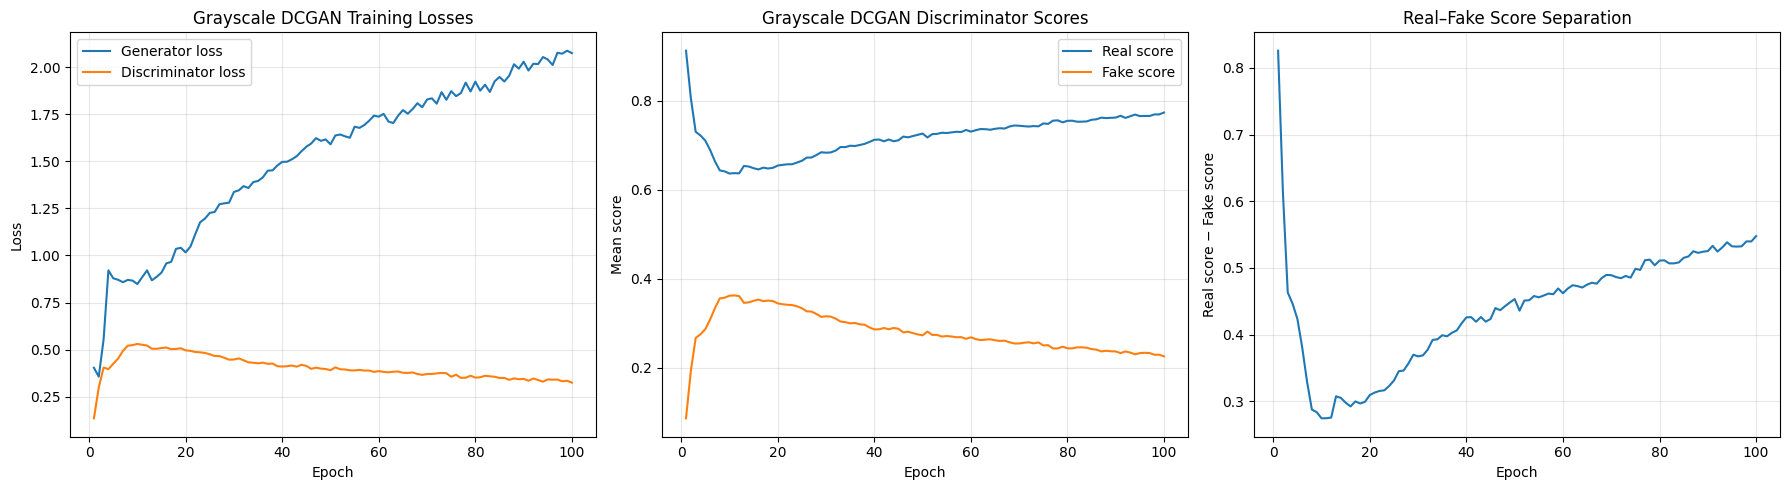

,Epoch phase,Generator loss mean,Generator loss SD,Discriminator loss mean,Discriminator loss SD,Real score mean,Fake score mean,Score separation mean,Epoch time mean seconds
0,1-20,0.8455,0.1883,0.4628,0.0968,0.6819,0.3176,0.3643,13.0944
1,21-40,1.3157,0.1237,0.4494,0.0259,0.6840,0.3157,0.3683,13.0229
2,41-60,1.6248,0.0706,0.3981,0.0109,0.7224,0.2773,0.4450,12.9119
3,61-80,1.8138,0.0632,0.3694,0.0109,0.7438,0.2559,0.4880,12.9743
4,81-100,1.9943,0.0680,0.3428,0.0097,0.7628,0.2370,0.5258,13.0368


Late epoch-81-to-100 score separation: 0.5258
Stability summary saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_stability_summary.csv
Training curves saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_training_curves.png
Eligible for final GAN selection: False
Visual and grayscale-reference FID evidence remain required.
Protected test set remains unused.


In [105]:
required_grayscale_stability_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_HISTORY_PATH",
    "GRAYSCALE_TARGET_EPOCHS",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "np",
    "pd",
    "plt",
    "Path",
]

missing_grayscale_stability_objects = [
    name
    for name in required_grayscale_stability_objects
    if name not in globals()
]

assert not missing_grayscale_stability_objects, (
    "Incomplete grayscale stability setup:\n"
    + "\n".join(
        missing_grayscale_stability_objects
    )
)


grayscale_stability_history_df = (
    pd.read_csv(
        GRAYSCALE_HISTORY_PATH
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)


required_grayscale_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


missing_grayscale_history_columns = [
    column
    for column in required_grayscale_history_columns
    if column
    not in grayscale_stability_history_df.columns
]


assert not missing_grayscale_history_columns, (
    "Grayscale history is missing:\n"
    + "\n".join(
        missing_grayscale_history_columns
    )
)


assert len(
    grayscale_stability_history_df
) == GRAYSCALE_TARGET_EPOCHS

assert np.array_equal(
    grayscale_stability_history_df[
        "epoch"
    ].to_numpy(dtype=np.int64),
    np.arange(
        1,
        GRAYSCALE_TARGET_EPOCHS + 1,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    grayscale_stability_history_df[
        required_grayscale_history_columns
    ].to_numpy(dtype=np.float64)
).all()


grayscale_stability_history_df[
    "score_separation"
] = (
    grayscale_stability_history_df[
        "real_score"
    ]
    - grayscale_stability_history_df[
        "fake_score"
    ]
)


grayscale_phase_specs = [
    (1, 20),
    (21, 40),
    (41, 60),
    (61, 80),
    (81, 100),
]


grayscale_phase_rows = []


for start_epoch, end_epoch in grayscale_phase_specs:
    phase_df = (
        grayscale_stability_history_df.loc[
            grayscale_stability_history_df[
                "epoch"
            ].between(
                start_epoch,
                end_epoch,
                inclusive="both",
            )
        ]
    )

    assert len(phase_df) == 20

    grayscale_phase_rows.append(
        {
            "Epoch phase": (
                f"{start_epoch}-{end_epoch}"
            ),
            "Generator loss mean": float(
                phase_df[
                    "generator_loss"
                ].mean()
            ),
            "Generator loss SD": float(
                phase_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Discriminator loss mean": float(
                phase_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Discriminator loss SD": float(
                phase_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Real score mean": float(
                phase_df[
                    "real_score"
                ].mean()
            ),
            "Fake score mean": float(
                phase_df[
                    "fake_score"
                ].mean()
            ),
            "Score separation mean": float(
                phase_df[
                    "score_separation"
                ].mean()
            ),
            "Epoch time mean seconds": float(
                phase_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


grayscale_stability_summary_df = pd.DataFrame(
    grayscale_phase_rows
)


GRAYSCALE_STABILITY_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "stability_summary.csv"
    )
)

GRAYSCALE_TRAINING_CURVES_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "training_curves.png"
    )
)


grayscale_stability_summary_df.to_csv(
    GRAYSCALE_STABILITY_SUMMARY_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


axes[0].plot(
    grayscale_stability_history_df["epoch"],
    grayscale_stability_history_df[
        "generator_loss"
    ],
    label="Generator loss",
)

axes[0].plot(
    grayscale_stability_history_df["epoch"],
    grayscale_stability_history_df[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

axes[0].set_title(
    "Grayscale DCGAN Training Losses"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    grayscale_stability_history_df["epoch"],
    grayscale_stability_history_df[
        "real_score"
    ],
    label="Real score",
)

axes[1].plot(
    grayscale_stability_history_df["epoch"],
    grayscale_stability_history_df[
        "fake_score"
    ],
    label="Fake score",
)

axes[1].set_title(
    "Grayscale DCGAN Discriminator Scores"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].plot(
    grayscale_stability_history_df["epoch"],
    grayscale_stability_history_df[
        "score_separation"
    ],
)

axes[2].set_title(
    "Real–Fake Score Separation"
)

axes[2].set_xlabel("Epoch")

axes[2].set_ylabel(
    "Real score − Fake score"
)

axes[2].grid(alpha=0.3)


figure.tight_layout()

figure.savefig(
    GRAYSCALE_TRAINING_CURVES_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


display(
    grayscale_stability_summary_df.round(4)
)


grayscale_late_history_df = (
    grayscale_stability_history_df.loc[
        grayscale_stability_history_df[
            "epoch"
        ].between(
            81,
            100,
            inclusive="both",
        )
    ]
)


GRAYSCALE_LATE_SCORE_SEPARATION = float(
    grayscale_late_history_df[
        "score_separation"
    ].mean()
)


print(
    "Late epoch-81-to-100 score separation:",
    f"{GRAYSCALE_LATE_SCORE_SEPARATION:.4f}",
)

print(
    "Stability summary saved:",
    GRAYSCALE_STABILITY_SUMMARY_PATH,
)

print(
    "Training curves saved:",
    GRAYSCALE_TRAINING_CURVES_PATH,
)

print(
    "Eligible for final GAN selection:",
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION,
)

print(
    "Visual and grayscale-reference FID "
    "evidence remain required."
)

print("Protected test set remains unused.")

In [106]:
required_grayscale_grid_review_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_MILESTONE_EPOCHS",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "GRIDS_DIR",
    "Path",
    "plt",
]

missing_grayscale_grid_review_objects = [
    name
    for name in required_grayscale_grid_review_objects
    if name not in globals()
]

assert not missing_grayscale_grid_review_objects, (
    "Incomplete grayscale grid-review setup:\n"
    + "\n".join(
        missing_grayscale_grid_review_objects
    )
)


grayscale_milestone_grid_paths = {
    epoch: (
        Path(GRIDS_DIR)
        / (
            f"{GRAYSCALE_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch in GRAYSCALE_MILESTONE_EPOCHS
}


for epoch, grid_path in (
    grayscale_milestone_grid_paths.items()
):
    assert grid_path.is_file(), (
        f"Missing grayscale epoch-{epoch} grid:\n"
        f"{grid_path}"
    )

    assert grid_path.stat().st_size > 0


figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14),
)


for axis, epoch in zip(
    axes.flat,
    GRAYSCALE_MILESTONE_EPOCHS,
):
    axis.imshow(
        plt.imread(
            grayscale_milestone_grid_paths[
                epoch
            ]
        )
    )

    axis.set_title(
        f"Epoch {epoch}",
        fontsize=14,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Discussion-Only Grayscale DCGAN "
        "Milestone Progression"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.97)
)

plt.show()
plt.close(figure)


print(
    "Displayed grayscale milestone grids:",
    GRAYSCALE_MILESTONE_EPOCHS,
)

print(
    "No visual-veto or checkpoint decision "
    "has been recorded yet."
)

print(
    "Eligible for final GAN selection:",
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION,
)

print(
    "Next step: construct the full "
    "grayscale training-reference FID statistics."
)

print("Protected test set remains unused.")

Displayed grayscale milestone grids: (50, 70, 90, 100)
No visual-veto or checkpoint decision has been recorded yet.
Eligible for final GAN selection: False
Next step: construct the full grayscale training-reference FID statistics.
Protected test set remains unused.


### 14.5 Grayscale Training-Reference FID Statistics

The grayscale experiment cannot be evaluated fairly against the normal RGB FID reference because converting CIFAR-10 to grayscale changes the real-data distribution.

A separate grayscale training reference is therefore constructed from all `50,000` CIFAR-10 training images.

The procedure is:

1. convert each RGB training image to one-channel luminance;
2. retain the same `32 × 32` spatial resolution;
3. convert the grayscale values to `uint8 [0, 255]`;
4. replicate the single grayscale channel three times only for compatibility with InceptionV3;
5. extract frozen 2,048-dimensional InceptionV3 features;
6. calculate and save the full-reference mean and covariance.

The same transformation will be applied to generated grayscale images before FID calculation.

This grayscale-reference FID answers whether generated grayscale images match the grayscale CIFAR-10 distribution. It is not directly interchangeable with the normal RGB FID values used for final GAN selection.

The experiment remains discussion-only and is not eligible for final GAN selection.

In [85]:
required_grayscale_fid_reference_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "x_train_grayscale_gan",
    "HISTORIES_DIR",
    "fid_feature_extractor",
    "extract_inception_features",
    "calculate_feature_statistics",
    "np",
    "pd",
    "Path",
    "gc",
]

missing_grayscale_fid_reference_objects = [
    name
    for name in required_grayscale_fid_reference_objects
    if name not in globals()
]

assert not missing_grayscale_fid_reference_objects, (
    "Incomplete grayscale FID-reference setup:\n"
    + "\n".join(
        missing_grayscale_fid_reference_objects
    )
)


GRAYSCALE_REAL_FID_REFERENCE_COUNT = 50_000

GRAYSCALE_FID_FEATURE_DIMENSION = 2_048

GRAYSCALE_FID_EXTRACTION_BATCH_SIZE = 64


assert x_train_grayscale_gan.shape == (
    GRAYSCALE_REAL_FID_REFERENCE_COUNT,
    32,
    32,
    1,
)

assert x_train_grayscale_gan.dtype == np.float32

assert np.isfinite(
    x_train_grayscale_gan
).all()

assert float(
    x_train_grayscale_gan.min()
) >= -1.0

assert float(
    x_train_grayscale_gan.max()
) <= 1.0


grayscale_real_images_uint8 = np.rint(
    np.clip(
        (
            x_train_grayscale_gan
            + 1.0
        )
        * 127.5,
        0.0,
        255.0,
    )
).astype(np.uint8)


assert grayscale_real_images_uint8.shape == (
    GRAYSCALE_REAL_FID_REFERENCE_COUNT,
    32,
    32,
    1,
)

assert (
    grayscale_real_images_uint8.dtype
    == np.uint8
)


grayscale_real_images_rgb_uint8 = np.repeat(
    grayscale_real_images_uint8,
    repeats=3,
    axis=-1,
)


assert grayscale_real_images_rgb_uint8.shape == (
    GRAYSCALE_REAL_FID_REFERENCE_COUNT,
    32,
    32,
    3,
)

assert np.array_equal(
    grayscale_real_images_rgb_uint8[
        :,
        :,
        :,
        0,
    ],
    grayscale_real_images_rgb_uint8[
        :,
        :,
        :,
        1,
    ],
)

assert np.array_equal(
    grayscale_real_images_rgb_uint8[
        :,
        :,
        :,
        1,
    ],
    grayscale_real_images_rgb_uint8[
        :,
        :,
        :,
        2,
    ],
)


grayscale_real_fid_features = (
    extract_inception_features(
        images_uint8=(
            grayscale_real_images_rgb_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=(
            GRAYSCALE_FID_EXTRACTION_BATCH_SIZE
        ),
    )
)


assert grayscale_real_fid_features.shape == (
    GRAYSCALE_REAL_FID_REFERENCE_COUNT,
    GRAYSCALE_FID_FEATURE_DIMENSION,
)

assert np.isfinite(
    grayscale_real_fid_features
).all()


(
    grayscale_real_fid_mean,
    grayscale_real_fid_covariance,
) = calculate_feature_statistics(
    grayscale_real_fid_features
)


assert grayscale_real_fid_mean.shape == (
    GRAYSCALE_FID_FEATURE_DIMENSION,
)

assert grayscale_real_fid_covariance.shape == (
    GRAYSCALE_FID_FEATURE_DIMENSION,
    GRAYSCALE_FID_FEATURE_DIMENSION,
)

assert np.isfinite(
    grayscale_real_fid_mean
).all()

assert np.isfinite(
    grayscale_real_fid_covariance
).all()


GRAYSCALE_REAL_FID_REFERENCE_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "training_reference_fid_statistics.npz"
    )
)


np.savez(
    GRAYSCALE_REAL_FID_REFERENCE_PATH,
    mean=grayscale_real_fid_mean,
    covariance=grayscale_real_fid_covariance,
    reference_count=np.asarray(
        [
            GRAYSCALE_REAL_FID_REFERENCE_COUNT
        ],
        dtype=np.int64,
    ),
    feature_dimension=np.asarray(
        [
            GRAYSCALE_FID_FEATURE_DIMENSION
        ],
        dtype=np.int64,
    ),
)


grayscale_fid_reference_summary_df = pd.DataFrame(
    [
        {
            "Reference": (
                "Full grayscale CIFAR-10 "
                "training distribution"
            ),
            "Reference image count": (
                GRAYSCALE_REAL_FID_REFERENCE_COUNT
            ),
            "Image representation": (
                "1-channel grayscale replicated "
                "to 3 channels for InceptionV3"
            ),
            "Feature dimension": (
                GRAYSCALE_FID_FEATURE_DIMENSION
            ),
            "Protected test images used": 0,
            "Eligible for final GAN selection": (
                GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
            ),
        }
    ]
)


display(
    grayscale_fid_reference_summary_df
)


print(
    "Grayscale training-reference "
    "FID statistics created."
)

print(
    "Reference image count:",
    GRAYSCALE_REAL_FID_REFERENCE_COUNT,
)

print(
    "Feature shape:",
    grayscale_real_fid_features.shape,
)

print(
    "Reference statistics saved:",
    GRAYSCALE_REAL_FID_REFERENCE_PATH,
)

print(
    "The normal RGB FID reference "
    "was not used."
)

print(
    "The grayscale experiment remains "
    "discussion-only."
)

print("Protected test set remains unused.")


del grayscale_real_images_uint8
del grayscale_real_images_rgb_uint8

gc.collect()

Extracting Inception features:   0%|          | 0/782 [00:00<?, ?it/s]

,Reference,Reference image count,Image representation,Feature dimension,Protected test images used,Eligible for final GAN selection
0,Full grayscale CIFAR-10 training distribution,50000,1-channel grayscale replicated to 3 channels f...,2048,0,False


Grayscale training-reference FID statistics created.
Reference image count: 50000
Feature shape: (50000, 2048)
Reference statistics saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_training_reference_fid_statistics.npz
The normal RGB FID reference was not used.
The grayscale experiment remains discussion-only.
Protected test set remains unused.


30882

### 14.6 Grayscale Milestone FID

The saved grayscale generators from epochs `50`, `70`, `90` and `100` are evaluated against the full grayscale-transformed CIFAR-10 training reference.

For each checkpoint:

- `5,000` grayscale images are generated using fixed seed `1001`;
- output remains one-channel during generation;
- values are converted to `uint8 [0, 255]`;
- the grayscale channel is replicated three times only for InceptionV3;
- FID is calculated using the grayscale training-reference mean and covariance.

The lowest milestone FID identifies the representative grayscale checkpoint, provided the visual and stability evidence gives no reason to reject it.

This selection only supports the discussion experiment. It does not enter final GAN selection.

In [54]:
required_grayscale_generation_objects = [
    "make_stateless_noise",
    "np",
]

missing_grayscale_generation_objects = [
    name
    for name in required_grayscale_generation_objects
    if name not in globals()
]

assert not missing_grayscale_generation_objects, (
    "Incomplete grayscale generation setup:\n"
    + "\n".join(
        missing_grayscale_generation_objects
    )
)


def generate_grayscale_images_uint8(
    generator,
    sample_count,
    latent_dim,
    seed,
    batch_size=64,
):
    sample_count = int(
        sample_count
    )

    latent_dim = int(
        latent_dim
    )

    batch_size = int(
        batch_size
    )


    noise = make_stateless_noise(
        sample_count=sample_count,
        latent_dim=latent_dim,
        seed=int(seed),
    )


    generated_batches = []


    for start_index in range(
        0,
        sample_count,
        batch_size,
    ):
        end_index = min(
            start_index + batch_size,
            sample_count,
        )

        generated_batch = generator(
            noise[
                start_index:end_index
            ],
            training=False,
        ).numpy()

        generated_batches.append(
            generated_batch
        )


    generated_images = np.concatenate(
        generated_batches,
        axis=0,
    )


    assert generated_images.shape == (
        sample_count,
        32,
        32,
        1,
    )

    assert np.isfinite(
        generated_images
    ).all()


    generated_images_uint8 = np.rint(
        np.clip(
            (
                generated_images
                + 1.0
            )
            * 127.5,
            0.0,
            255.0,
        )
    ).astype(np.uint8)


    assert generated_images_uint8.shape == (
        sample_count,
        32,
        32,
        1,
    )

    assert (
        generated_images_uint8.dtype
        == np.uint8
    )


    return generated_images_uint8


print(
    "Grayscale generation helper ready."
)

print(
    "Generated images remain one-channel "
    "until feature extraction."
)

Grayscale generation helper ready.
Generated images remain one-channel until feature extraction.


In [109]:
required_grayscale_milestone_fid_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_MILESTONE_EPOCHS",
    "GRAYSCALE_GENERATOR_PARAMETERS",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "build_grayscale_dcgan_generator",
    "generate_grayscale_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "grayscale_real_fid_mean",
    "grayscale_real_fid_covariance",
    "np",
    "pd",
    "Path",
    "gc",
]

missing_grayscale_milestone_fid_objects = [
    name
    for name in required_grayscale_milestone_fid_objects
    if name not in globals()
]

assert not missing_grayscale_milestone_fid_objects, (
    "Incomplete grayscale milestone-FID setup:\n"
    + "\n".join(
        missing_grayscale_milestone_fid_objects
    )
)


GRAYSCALE_MILESTONE_FID_SEED = 1001

GRAYSCALE_MILESTONE_FID_SAMPLE_COUNT = 5_000

GRAYSCALE_MILESTONE_FID_BATCH_SIZE = 64


grayscale_milestone_fid_generator = (
    build_grayscale_dcgan_generator(
        GRAYSCALE_LATENT_DIM
    )
)


assert int(
    grayscale_milestone_fid_generator.count_params()
) == GRAYSCALE_GENERATOR_PARAMETERS


grayscale_milestone_fid_rows = []


for milestone_epoch in (
    GRAYSCALE_MILESTONE_EPOCHS
):
    milestone_generator_path = (
        Path(WEIGHTS_DIR)
        / (
            f"{GRAYSCALE_RUN_ID}_"
            f"epoch{milestone_epoch:03d}_"
            "generator.weights.h5"
        )
    )


    assert milestone_generator_path.is_file(), (
        f"Missing grayscale epoch-{milestone_epoch} "
        "generator weights:\n"
        f"{milestone_generator_path}"
    )


    grayscale_milestone_fid_generator.load_weights(
        milestone_generator_path
    )


    grayscale_generated_images_uint8 = (
        generate_grayscale_images_uint8(
            generator=(
                grayscale_milestone_fid_generator
            ),
            sample_count=(
                GRAYSCALE_MILESTONE_FID_SAMPLE_COUNT
            ),
            latent_dim=(
                GRAYSCALE_LATENT_DIM
            ),
            seed=(
                GRAYSCALE_MILESTONE_FID_SEED
            ),
            batch_size=(
                GRAYSCALE_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    grayscale_generated_rgb_uint8 = np.repeat(
        grayscale_generated_images_uint8,
        repeats=3,
        axis=-1,
    )


    assert grayscale_generated_rgb_uint8.shape == (
        GRAYSCALE_MILESTONE_FID_SAMPLE_COUNT,
        32,
        32,
        3,
    )


    grayscale_generated_fid_features = (
        extract_inception_features(
            images_uint8=(
                grayscale_generated_rgb_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                GRAYSCALE_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    assert grayscale_generated_fid_features.shape == (
        GRAYSCALE_MILESTONE_FID_SAMPLE_COUNT,
        2_048,
    )

    assert np.isfinite(
        grayscale_generated_fid_features
    ).all()


    (
        grayscale_generated_fid_mean,
        grayscale_generated_fid_covariance,
    ) = calculate_feature_statistics(
        grayscale_generated_fid_features
    )


    grayscale_milestone_fid = float(
        calculate_fid_from_statistics(
            grayscale_real_fid_mean,
            grayscale_real_fid_covariance,
            grayscale_generated_fid_mean,
            grayscale_generated_fid_covariance,
        )
    )


    assert np.isfinite(
        grayscale_milestone_fid
    )

    assert grayscale_milestone_fid >= 0.0


    grayscale_milestone_fid_rows.append(
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Evaluation": (
                "grayscale_reference_milestone_fid"
            ),
            "Epoch": milestone_epoch,
            "Seed": (
                GRAYSCALE_MILESTONE_FID_SEED
            ),
            "Generated sample count": (
                GRAYSCALE_MILESTONE_FID_SAMPLE_COUNT
            ),
            "Real reference count": (
                GRAYSCALE_REAL_FID_REFERENCE_COUNT
            ),
            "FID": grayscale_milestone_fid,
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
        }
    )


    print(
        f"Epoch {milestone_epoch:03d} "
        "grayscale-reference FID: "
        f"{grayscale_milestone_fid:.4f}"
    )


    del grayscale_generated_images_uint8
    del grayscale_generated_rgb_uint8
    del grayscale_generated_fid_features
    del grayscale_generated_fid_mean
    del grayscale_generated_fid_covariance

    gc.collect()


grayscale_milestone_fid_df = pd.DataFrame(
    grayscale_milestone_fid_rows
)


GRAYSCALE_MILESTONE_FID_RESULTS_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "milestone_grayscale_reference_fid.csv"
    )
)


grayscale_milestone_fid_df.to_csv(
    GRAYSCALE_MILESTONE_FID_RESULTS_PATH,
    index=False,
)


GRAYSCALE_LOWEST_FID_EPOCH = int(
    grayscale_milestone_fid_df.loc[
        grayscale_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

GRAYSCALE_LOWEST_MILESTONE_FID = float(
    grayscale_milestone_fid_df[
        "FID"
    ].min()
)


display(
    grayscale_milestone_fid_df.round(4)
)


print(
    "Lowest grayscale milestone-FID epoch:",
    GRAYSCALE_LOWEST_FID_EPOCH,
)

print(
    "Lowest grayscale milestone FID:",
    f"{GRAYSCALE_LOWEST_MILESTONE_FID:.4f}",
)

print(
    "Results saved:",
    GRAYSCALE_MILESTONE_FID_RESULTS_PATH,
)

print(
    "This result is only comparable "
    "within the grayscale experiment."
)

print(
    "It does not compete with the "
    "RGB final-model candidates."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 grayscale-reference FID: 27.5943


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 grayscale-reference FID: 25.4282


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 grayscale-reference FID: 23.1315


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 grayscale-reference FID: 21.8382


,Run ID,Evaluation,Epoch,Seed,Generated sample count,Real reference count,FID,Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,grayscale_reference_milestone_fid,50,1001,5000,50000,27.5943,True,False
1,G12_grayscale_fliptranslation_seed42,grayscale_reference_milestone_fid,70,1001,5000,50000,25.4282,True,False
2,G12_grayscale_fliptranslation_seed42,grayscale_reference_milestone_fid,90,1001,5000,50000,23.1315,True,False
3,G12_grayscale_fliptranslation_seed42,grayscale_reference_milestone_fid,100,1001,5000,50000,21.8382,True,False


Lowest grayscale milestone-FID epoch: 100
Lowest grayscale milestone FID: 21.8382
Results saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_milestone_grayscale_reference_fid.csv
This result is only comparable within the grayscale experiment.
It does not compete with the RGB final-model candidates.
Protected test set remains unused.


### 14.7 Representative Grayscale Checkpoint Selection

The grayscale-reference FID improved at every evaluated milestone:

| Epoch | Grayscale-reference FID |
|---:|---:|
| 50 | 27.5943 |
| 70 | 25.4282 |
| 90 | 23.1315 |
| 100 | **21.8382** |

The saved grids also showed continued, although modest, refinement through epoch `100`. No mode collapse, severe repetition or late qualitative deterioration was observed.

The adversarial trajectory remained finite and gradual. Mean real-minus-fake score separation reached `0.5258` during epochs `81–100`, but this coincided with continued FID improvement rather than deterioration.

No visual or stability override is therefore justified.

Epoch `100` is selected as the representative grayscale checkpoint for the discussion experiment.

This selection does not make the grayscale model eligible for final GAN selection. Its FID uses a grayscale-transformed real reference and is not numerically interchangeable with the RGB FID values.

In [110]:
required_grayscale_selection_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_TRAINING_SEED",
    "GRAYSCALE_MILESTONE_EPOCHS",
    "GRAYSCALE_LOWEST_FID_EPOCH",
    "GRAYSCALE_LOWEST_MILESTONE_FID",
    "GRAYSCALE_LATE_SCORE_SEPARATION",
    "GRAYSCALE_TRAINING_TIME_MINUTES",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "pd",
]

missing_grayscale_selection_objects = [
    name
    for name in required_grayscale_selection_objects
    if name not in globals()
]

assert not missing_grayscale_selection_objects, (
    "Incomplete grayscale checkpoint-selection setup:\n"
    + "\n".join(
        missing_grayscale_selection_objects
    )
)


GRAYSCALE_SELECTED_EPOCH = int(
    GRAYSCALE_LOWEST_FID_EPOCH
)

GRAYSCALE_SELECTED_MILESTONE_FID = float(
    GRAYSCALE_LOWEST_MILESTONE_FID
)

GRAYSCALE_VISUAL_VETO = False
GRAYSCALE_STABILITY_VETO = False
GRAYSCALE_SELECTION_OVERRIDE = False


assert GRAYSCALE_SELECTED_EPOCH == 100

assert (
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
    is False
)


GRAYSCALE_SELECTED_MILESTONE_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        f"epoch{GRAYSCALE_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

GRAYSCALE_SELECTED_MILESTONE_DISCRIMINATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        f"epoch{GRAYSCALE_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


assert (
    GRAYSCALE_SELECTED_MILESTONE_GENERATOR_PATH
    .is_file()
)

assert (
    GRAYSCALE_SELECTED_MILESTONE_DISCRIMINATOR_PATH
    .is_file()
)


grayscale_checkpoint_selection_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Training seed": (
                GRAYSCALE_TRAINING_SEED
            ),
            "Selected epoch": (
                GRAYSCALE_SELECTED_EPOCH
            ),
            "Selected grayscale-reference FID": (
                GRAYSCALE_SELECTED_MILESTONE_FID
            ),
            "Late score separation": (
                GRAYSCALE_LATE_SCORE_SEPARATION
            ),
            "Training time minutes": (
                GRAYSCALE_TRAINING_TIME_MINUTES
            ),
            "Visual veto": (
                GRAYSCALE_VISUAL_VETO
            ),
            "Stability veto": (
                GRAYSCALE_STABILITY_VETO
            ),
            "Selection override": (
                GRAYSCALE_SELECTION_OVERRIDE
            ),
            "Experiment role": (
                "Discussion-only sensitivity analysis"
            ),
            "Eligible for final GAN selection": False,
            "Decision": (
                "Epoch 100 selected because it had the "
                "lowest grayscale-reference FID and no "
                "visual or stability safeguard justified "
                "overriding the quantitative result."
            ),
        }
    ]
)


GRAYSCALE_CHECKPOINT_SELECTION_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "checkpoint_selection.csv"
    )
)


grayscale_checkpoint_selection_df.to_csv(
    GRAYSCALE_CHECKPOINT_SELECTION_PATH,
    index=False,
)


display(
    grayscale_checkpoint_selection_df.round(4)
)


print(
    "Representative grayscale epoch:",
    GRAYSCALE_SELECTED_EPOCH,
)

print(
    "Selected grayscale-reference FID:",
    f"{GRAYSCALE_SELECTED_MILESTONE_FID:.4f}",
)

print(
    "Visual veto:",
    GRAYSCALE_VISUAL_VETO,
)

print(
    "Stability veto:",
    GRAYSCALE_STABILITY_VETO,
)

print(
    "Eligible for final GAN selection:",
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION,
)

print(
    "Selection record saved:",
    GRAYSCALE_CHECKPOINT_SELECTION_PATH,
)

print("Protected test set remains unused.")

,Run ID,Training seed,Selected epoch,Selected grayscale-reference FID,Late score separation,Training time minutes,Visual veto,Stability veto,Selection override,Experiment role,Eligible for final GAN selection,Decision
0,G12_grayscale_fliptranslation_seed42,42,100,21.8382,0.5258,21.6801,False,False,False,Discussion-only sensitivity analysis,False,Epoch 100 selected because it had the lowest g...


Representative grayscale epoch: 100
Selected grayscale-reference FID: 21.8382
Visual veto: False
Stability veto: False
Eligible for final GAN selection: False
Selection record saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_checkpoint_selection.csv
Protected test set remains unused.


### 14.8 Selected Grayscale Weights and Reload Verification

The representative epoch-100 generator and discriminator are copied into stable selected-weight files.

Fresh grayscale generator and discriminator instances are then reconstructed and loaded from those files.

The generator is checked using fixed latent vectors. The discriminator is checked using the same generated-image tensors before and after reloading.

This verifies that the discussion model can be reconstructed independently of the training runtime.

In [111]:
required_grayscale_selected_weight_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_SELECTED_EPOCH",
    "GRAYSCALE_SELECTED_MILESTONE_GENERATOR_PATH",
    "GRAYSCALE_SELECTED_MILESTONE_DISCRIMINATOR_PATH",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_GENERATOR_PARAMETERS",
    "GRAYSCALE_DISCRIMINATOR_PARAMETERS",
    "WEIGHTS_DIR",
    "build_grayscale_dcgan_generator",
    "build_grayscale_augmented_discriminator",
]

missing_grayscale_selected_weight_objects = [
    name
    for name in required_grayscale_selected_weight_objects
    if name not in globals()
]

assert not missing_grayscale_selected_weight_objects, (
    "Incomplete grayscale selected-weight setup:\n"
    + "\n".join(
        missing_grayscale_selected_weight_objects
    )
)


grayscale_selected_generator = (
    build_grayscale_dcgan_generator(
        GRAYSCALE_LATENT_DIM
    )
)

grayscale_selected_discriminator = (
    build_grayscale_augmented_discriminator()
)


assert int(
    grayscale_selected_generator.count_params()
) == GRAYSCALE_GENERATOR_PARAMETERS

assert int(
    grayscale_selected_discriminator.count_params()
) == GRAYSCALE_DISCRIMINATOR_PARAMETERS


grayscale_selected_generator.load_weights(
    GRAYSCALE_SELECTED_MILESTONE_GENERATOR_PATH
)

grayscale_selected_discriminator.load_weights(
    GRAYSCALE_SELECTED_MILESTONE_DISCRIMINATOR_PATH
)


GRAYSCALE_SELECTED_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "generator.weights.h5"
    )
)

GRAYSCALE_SELECTED_DISCRIMINATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "discriminator.weights.h5"
    )
)


grayscale_selected_generator.save_weights(
    GRAYSCALE_SELECTED_GENERATOR_PATH
)

grayscale_selected_discriminator.save_weights(
    GRAYSCALE_SELECTED_DISCRIMINATOR_PATH
)


for selected_path in [
    GRAYSCALE_SELECTED_GENERATOR_PATH,
    GRAYSCALE_SELECTED_DISCRIMINATOR_PATH,
]:
    assert selected_path.is_file()
    assert selected_path.stat().st_size > 0


print(
    "Selected grayscale generator saved:",
    GRAYSCALE_SELECTED_GENERATOR_PATH,
)

print(
    "Selected grayscale discriminator saved:",
    GRAYSCALE_SELECTED_DISCRIMINATOR_PATH,
)

print(
    "The grayscale model remains discussion-only."
)

print("Protected test set remains unused.")

Selected grayscale generator saved: [local project directory]/weights/G12_grayscale_fliptranslation_seed42_generator.weights.h5
Selected grayscale discriminator saved: [local project directory]/weights/G12_grayscale_fliptranslation_seed42_discriminator.weights.h5
The grayscale model remains discussion-only.
Protected test set remains unused.


In [112]:
required_grayscale_reload_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_SELECTED_EPOCH",
    "GRAYSCALE_SELECTED_GENERATOR_PATH",
    "GRAYSCALE_SELECTED_DISCRIMINATOR_PATH",
    "GRAYSCALE_LATENT_DIM",
    "grayscale_selected_generator",
    "grayscale_selected_discriminator",
    "build_grayscale_dcgan_generator",
    "build_grayscale_augmented_discriminator",
    "make_stateless_noise",
    "HISTORIES_DIR",
    "tf",
    "np",
    "pd",
]

missing_grayscale_reload_objects = [
    name
    for name in required_grayscale_reload_objects
    if name not in globals()
]

assert not missing_grayscale_reload_objects, (
    "Incomplete grayscale reload-verification setup:\n"
    + "\n".join(
        missing_grayscale_reload_objects
    )
)


GRAYSCALE_RELOAD_PROBE_SEED = 1601
GRAYSCALE_RELOAD_PROBE_COUNT = 20


grayscale_reload_probe_noise = (
    make_stateless_noise(
        sample_count=(
            GRAYSCALE_RELOAD_PROBE_COUNT
        ),
        latent_dim=GRAYSCALE_LATENT_DIM,
        seed=GRAYSCALE_RELOAD_PROBE_SEED,
    )
)


grayscale_outputs_before_reload = (
    grayscale_selected_generator(
        grayscale_reload_probe_noise,
        training=False,
    )
    .numpy()
)


grayscale_scores_before_reload = (
    grayscale_selected_discriminator(
        tf.convert_to_tensor(
            grayscale_outputs_before_reload,
            dtype=tf.float32,
        ),
        training=False,
    )
    .numpy()
)


grayscale_reloaded_generator = (
    build_grayscale_dcgan_generator(
        GRAYSCALE_LATENT_DIM
    )
)

grayscale_reloaded_discriminator = (
    build_grayscale_augmented_discriminator()
)


grayscale_reloaded_generator.load_weights(
    GRAYSCALE_SELECTED_GENERATOR_PATH
)

grayscale_reloaded_discriminator.load_weights(
    GRAYSCALE_SELECTED_DISCRIMINATOR_PATH
)


grayscale_outputs_after_reload = (
    grayscale_reloaded_generator(
        grayscale_reload_probe_noise,
        training=False,
    )
    .numpy()
)


grayscale_scores_after_reload = (
    grayscale_reloaded_discriminator(
        tf.convert_to_tensor(
            grayscale_outputs_before_reload,
            dtype=tf.float32,
        ),
        training=False,
    )
    .numpy()
)


GRAYSCALE_GENERATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            grayscale_outputs_before_reload
            - grayscale_outputs_after_reload
        )
    )
)

GRAYSCALE_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            grayscale_scores_before_reload
            - grayscale_scores_after_reload
        )
    )
)


assert grayscale_outputs_before_reload.shape == (
    GRAYSCALE_RELOAD_PROBE_COUNT,
    32,
    32,
    1,
)

assert grayscale_scores_before_reload.shape == (
    GRAYSCALE_RELOAD_PROBE_COUNT,
    1,
)

assert np.isfinite(
    grayscale_outputs_after_reload
).all()

assert np.isfinite(
    grayscale_scores_after_reload
).all()

assert (
    GRAYSCALE_GENERATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)

assert (
    GRAYSCALE_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
    <= 1e-5
)


grayscale_reload_audit_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Selected epoch": (
                GRAYSCALE_SELECTED_EPOCH
            ),
            "Probe seed": (
                GRAYSCALE_RELOAD_PROBE_SEED
            ),
            "Probe count": (
                GRAYSCALE_RELOAD_PROBE_COUNT
            ),
            "Generator output maximum difference": (
                GRAYSCALE_GENERATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Discriminator output maximum difference": (
                GRAYSCALE_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE
            ),
            "Generator reload passed": True,
            "Discriminator reload passed": True,
            "Discussion-only": True,
        }
    ]
)


GRAYSCALE_RELOAD_AUDIT_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "selected_reload_audit.csv"
    )
)


grayscale_reload_audit_df.to_csv(
    GRAYSCALE_RELOAD_AUDIT_PATH,
    index=False,
)


display(
    grayscale_reload_audit_df.round(10)
)


print(
    "Generator reload maximum difference:",
    f"{GRAYSCALE_GENERATOR_RELOAD_MAX_DIFFERENCE:.10f}",
)

print(
    "Discriminator reload maximum difference:",
    f"{GRAYSCALE_DISCRIMINATOR_RELOAD_MAX_DIFFERENCE:.10f}",
)

print(
    "Selected grayscale networks "
    "reloaded successfully."
)

print(
    "Reload audit saved:",
    GRAYSCALE_RELOAD_AUDIT_PATH,
)

print("Protected test set remains unused.")

,Run ID,Selected epoch,Probe seed,Probe count,Generator output maximum difference,Discriminator output maximum difference,Generator reload passed,Discriminator reload passed,Discussion-only
0,G12_grayscale_fliptranslation_seed42,100,1601,20,0.0,0.0,True,True,True


Generator reload maximum difference: 0.0000000000
Discriminator reload maximum difference: 0.0000000000
Selected grayscale networks reloaded successfully.
Reload audit saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_selected_reload_audit.csv
Protected test set remains unused.


### 14.9 Repeated Grayscale-Reference FID

The representative epoch-100 grayscale generator is evaluated using generation seeds `1002`, `1003` and `1004`.

Each repeat generates `5,000` one-channel images. The grayscale channel is replicated three times only for frozen InceptionV3 feature extraction.

FID is calculated against the full grayscale-transformed CIFAR-10 training reference.

The resulting mean and sample standard deviation estimate generated-sample variation for the fixed representative grayscale checkpoint.

These values remain internal to the discussion experiment and cannot be ranked directly against RGB FID.

In [86]:
required_grayscale_repeated_fid_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_SELECTED_EPOCH",
    "GRAYSCALE_LATENT_DIM",
    "grayscale_reloaded_generator",
    "grayscale_real_fid_mean",
    "grayscale_real_fid_covariance",
    "generate_grayscale_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "fid_feature_extractor",
    "HISTORIES_DIR",
    "np",
    "pd",
    "gc",
]

missing_grayscale_repeated_fid_objects = [
    name
    for name in required_grayscale_repeated_fid_objects
    if name not in globals()
]

assert not missing_grayscale_repeated_fid_objects, (
    "Incomplete grayscale repeated-FID setup:\n"
    + "\n".join(
        missing_grayscale_repeated_fid_objects
    )
)


GRAYSCALE_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

GRAYSCALE_REPEATED_FID_SAMPLE_COUNT = 5_000
GRAYSCALE_REPEATED_FID_BATCH_SIZE = 64


grayscale_repeated_fid_rows = []


for repeat_index, fid_seed in enumerate(
    GRAYSCALE_REPEATED_FID_SEEDS,
    start=1,
):
    grayscale_repeat_images_uint8 = (
        generate_grayscale_images_uint8(
            generator=(
                grayscale_reloaded_generator
            ),
            sample_count=(
                GRAYSCALE_REPEATED_FID_SAMPLE_COUNT
            ),
            latent_dim=GRAYSCALE_LATENT_DIM,
            seed=fid_seed,
            batch_size=(
                GRAYSCALE_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    grayscale_repeat_rgb_uint8 = np.repeat(
        grayscale_repeat_images_uint8,
        repeats=3,
        axis=-1,
    )


    grayscale_repeat_features = (
        extract_inception_features(
            images_uint8=(
                grayscale_repeat_rgb_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                GRAYSCALE_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    assert grayscale_repeat_features.shape == (
        GRAYSCALE_REPEATED_FID_SAMPLE_COUNT,
        2_048,
    )

    assert np.isfinite(
        grayscale_repeat_features
    ).all()


    (
        grayscale_repeat_mean,
        grayscale_repeat_covariance,
    ) = calculate_feature_statistics(
        grayscale_repeat_features
    )


    grayscale_repeat_fid = float(
        calculate_fid_from_statistics(
            grayscale_real_fid_mean,
            grayscale_real_fid_covariance,
            grayscale_repeat_mean,
            grayscale_repeat_covariance,
        )
    )


    assert np.isfinite(
        grayscale_repeat_fid
    )

    assert grayscale_repeat_fid >= 0.0


    grayscale_repeated_fid_rows.append(
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Selected epoch": (
                GRAYSCALE_SELECTED_EPOCH
            ),
            "Repeat": repeat_index,
            "Seed": fid_seed,
            "Generated sample count": (
                GRAYSCALE_REPEATED_FID_SAMPLE_COUNT
            ),
            "Real reference count": 50_000,
            "Grayscale-reference FID": (
                grayscale_repeat_fid
            ),
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
        }
    )


    print(
        f"Repeat {repeat_index} "
        f"| seed {fid_seed} "
        "| grayscale-reference FID: "
        f"{grayscale_repeat_fid:.4f}"
    )


    del grayscale_repeat_images_uint8
    del grayscale_repeat_rgb_uint8
    del grayscale_repeat_features
    del grayscale_repeat_mean
    del grayscale_repeat_covariance

    gc.collect()


grayscale_repeated_fid_df = pd.DataFrame(
    grayscale_repeated_fid_rows
)


GRAYSCALE_REPEATED_FID_MEAN = float(
    grayscale_repeated_fid_df[
        "Grayscale-reference FID"
    ].mean()
)

GRAYSCALE_REPEATED_FID_SD = float(
    grayscale_repeated_fid_df[
        "Grayscale-reference FID"
    ].std(ddof=1)
)

GRAYSCALE_REPEATED_FID_MINIMUM = float(
    grayscale_repeated_fid_df[
        "Grayscale-reference FID"
    ].min()
)

GRAYSCALE_REPEATED_FID_MAXIMUM = float(
    grayscale_repeated_fid_df[
        "Grayscale-reference FID"
    ].max()
)

GRAYSCALE_REPEATED_FID_RANGE = float(
    GRAYSCALE_REPEATED_FID_MAXIMUM
    - GRAYSCALE_REPEATED_FID_MINIMUM
)


grayscale_repeated_fid_summary_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Selected epoch": (
                GRAYSCALE_SELECTED_EPOCH
            ),
            "Repeat count": 3,
            "Seeds": str(
                GRAYSCALE_REPEATED_FID_SEEDS
            ),
            "Sample count per repeat": (
                GRAYSCALE_REPEATED_FID_SAMPLE_COUNT
            ),
            "Repeated grayscale-reference FID mean": (
                GRAYSCALE_REPEATED_FID_MEAN
            ),
            "Repeated grayscale-reference FID SD": (
                GRAYSCALE_REPEATED_FID_SD
            ),
            "Minimum FID": (
                GRAYSCALE_REPEATED_FID_MINIMUM
            ),
            "Maximum FID": (
                GRAYSCALE_REPEATED_FID_MAXIMUM
            ),
            "FID range": (
                GRAYSCALE_REPEATED_FID_RANGE
            ),
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
        }
    ]
)


GRAYSCALE_REPEATED_FID_RESULTS_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "repeated_grayscale_reference_fid.csv"
    )
)

GRAYSCALE_REPEATED_FID_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "repeated_grayscale_reference_fid_summary.csv"
    )
)


grayscale_repeated_fid_df.to_csv(
    GRAYSCALE_REPEATED_FID_RESULTS_PATH,
    index=False,
)

grayscale_repeated_fid_summary_df.to_csv(
    GRAYSCALE_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    grayscale_repeated_fid_df.round(4)
)

display(
    grayscale_repeated_fid_summary_df.round(4)
)


print(
    "Repeated grayscale-reference FID:",
    (
        f"{GRAYSCALE_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{GRAYSCALE_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "FID range:",
    f"{GRAYSCALE_REPEATED_FID_RANGE:.4f}",
)

print(
    "The result is not directly comparable "
    "with RGB FID."
)

print(
    "The model remains discussion-only."
)

print("Protected test set remains unused.")

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 1 | seed 1002 | grayscale-reference FID: 21.9689


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 2 | seed 1003 | grayscale-reference FID: 22.2318


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Repeat 3 | seed 1004 | grayscale-reference FID: 22.0153


,Run ID,Selected epoch,Repeat,Seed,Generated sample count,Real reference count,Grayscale-reference FID,Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,100,1,1002,5000,50000,21.9689,True,False
1,G12_grayscale_fliptranslation_seed42,100,2,1003,5000,50000,22.2318,True,False
2,G12_grayscale_fliptranslation_seed42,100,3,1004,5000,50000,22.0153,True,False


,Run ID,Selected epoch,Repeat count,Seeds,Sample count per repeat,Repeated grayscale-reference FID mean,Repeated grayscale-reference FID SD,Minimum FID,Maximum FID,FID range,Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,100,3,"(1002, 1003, 1004)",5000,22.072,0.1403,21.9689,22.2318,0.2629,True,False


Repeated grayscale-reference FID: 22.0720 ± 0.1403
FID range: 0.2629
The result is not directly comparable with RGB FID.
The model remains discussion-only.
Protected test set remains unused.


### 14.10 Strict Grayscale Structural-Recognisability Assessment

FID measures distribution-level similarity but does not directly determine whether individual generated images contain coherent and recognisable object structure.

The selected grayscale generator is therefore evaluated using a fixed, unfiltered set of `100` generated images produced with seed `1201`.

Each image is assigned exactly one quality category:

- **Clear**: a coherent and readily recognisable object or scene is visible;
- **Marginal**: meaningful object-like structure is present, but the image remains ambiguous, distorted or difficult to identify confidently;
- **Nonsense**: no coherent object or scene can be identified.

The scoring focuses on structural recognisability rather than requested-class correctness because the grayscale model is unconditional.

The lack of colour is not by itself grounds for assigning an image to the Nonsense category. However, if removing colour makes otherwise ambiguous structures harder to recognise, that effect remains part of the final grayscale-versus-RGB interpretation.

The images are displayed without classifier filtering, rejection sampling or manual curation.

The approximate manual-resolution threshold remains `13` images out of `100`. Differences smaller than this threshold are treated cautiously rather than as strong evidence of improved recognisability.

The experiment remains discussion-only and is not eligible for final GAN selection.

In [56]:
required_grayscale_manual_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_SELECTED_EPOCH",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "grayscale_reloaded_generator",
    "generate_grayscale_images_uint8",
    "GRIDS_DIR",
    "np",
    "plt",
    "Path",
]

missing_grayscale_manual_objects = [
    name
    for name in required_grayscale_manual_objects
    if name not in globals()
]

assert not missing_grayscale_manual_objects, (
    "Incomplete grayscale manual-assessment setup:\n"
    + "\n".join(
        missing_grayscale_manual_objects
    )
)


GRAYSCALE_MANUAL_EVALUATION_SEED = 1201

GRAYSCALE_MANUAL_SAMPLE_COUNT = 100

GRAYSCALE_MANUAL_GRID_ROWS = 10

GRAYSCALE_MANUAL_GRID_COLUMNS = 10

GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD = 13


assert (
    GRAYSCALE_MANUAL_GRID_ROWS
    * GRAYSCALE_MANUAL_GRID_COLUMNS
    == GRAYSCALE_MANUAL_SAMPLE_COUNT
)

assert (
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
    is False
)


grayscale_manual_images_uint8 = (
    generate_grayscale_images_uint8(
        generator=(
            grayscale_reloaded_generator
        ),
        sample_count=(
            GRAYSCALE_MANUAL_SAMPLE_COUNT
        ),
        latent_dim=GRAYSCALE_LATENT_DIM,
        seed=GRAYSCALE_MANUAL_EVALUATION_SEED,
        batch_size=64,
    )
)


assert grayscale_manual_images_uint8.shape == (
    GRAYSCALE_MANUAL_SAMPLE_COUNT,
    32,
    32,
    1,
)

assert (
    grayscale_manual_images_uint8.dtype
    == np.uint8
)

assert np.isfinite(
    grayscale_manual_images_uint8
).all()


GRAYSCALE_MANUAL_INDEXED_GRID_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "manual_quality_indexed_10x10.png"
    )
)


figure, axes = plt.subplots(
    GRAYSCALE_MANUAL_GRID_ROWS,
    GRAYSCALE_MANUAL_GRID_COLUMNS,
    figsize=(16, 16),
    squeeze=False,
)


for image_index, axis in enumerate(
    axes.flat
):
    axis.imshow(
        grayscale_manual_images_uint8[
            image_index,
            :,
            :,
            0,
        ],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axis.set_title(
        str(image_index),
        fontsize=8,
        pad=2,
    )

    axis.axis("off")


figure.suptitle(
    (
        "Discussion-Only Grayscale DCGAN "
        "Manual Structural Assessment\n"
        f"Epoch {GRAYSCALE_SELECTED_EPOCH}, "
        f"Generation Seed "
        f"{GRAYSCALE_MANUAL_EVALUATION_SEED}"
    ),
    fontsize=17,
)


figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.965)
)


figure.savefig(
    GRAYSCALE_MANUAL_INDEXED_GRID_PATH,
    dpi=190,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


print(
    "Grayscale manual-assessment pool created."
)

print(
    "Evaluation seed:",
    GRAYSCALE_MANUAL_EVALUATION_SEED,
)

print(
    "Image count:",
    GRAYSCALE_MANUAL_SAMPLE_COUNT,
)

print(
    "Indexed grid saved:",
    GRAYSCALE_MANUAL_INDEXED_GRID_PATH,
)

print()

print(
    "Score every image exactly once as:"
)

print(
    "Clear, Marginal or Nonsense."
)

print(
    "Manual-resolution threshold:",
    GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD,
    "images out of 100",
)

print(
    "No classifier filtering, rejection "
    "or manual curation was applied."
)

print(
    "The grayscale model remains discussion-only."
)

print("Protected test set remains unused.")

Grayscale manual-assessment pool created.
Evaluation seed: 1201
Image count: 100
Indexed grid saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_manual_quality_indexed_10x10.png

Score every image exactly once as:
Clear, Marginal or Nonsense.
Manual-resolution threshold: 13 images out of 100
No classifier filtering, rejection or manual curation was applied.
The grayscale model remains discussion-only.
Protected test set remains unused.


### 14.11 Grayscale Manual Structural-Recognisability Results

The fixed 100-image grayscale pool was scored using the same strict Clear / Marginal / Nonsense rubric used for the selected RGB unconditional GAN.

The grayscale result was:

- **Clear: 40 / 100**
- **Marginal: 51 / 100**
- **Nonsense: 9 / 100**

The selected RGB unconditional GAN previously achieved:

- **Clear: 22 / 100**
- **Marginal: 70 / 100**
- **Nonsense: 8 / 100**

The grayscale model therefore produced `18` more Clear images. This exceeds the approximate manual-resolution threshold of `13` images, so the difference is large enough to support a meaningful structural-recognisability effect rather than being treated as a practical tie.

The Nonsense count remained almost unchanged (`9` versus `8`). The main effect of removing colour therefore appears to be a shift from ambiguous Marginal images toward more readily recognisable structure, rather than the elimination of complete generation failures.

This supports the hypothesis that reducing the image from three colour channels to one grayscale channel simplifies the generation problem and allows the fixed-capacity DCGAN to represent object shape and contrast more clearly.

However, this improvement comes at the explicit cost of all colour information. The grayscale model also uses its own grayscale-transformed FID reference, so its lower numerical FID cannot be ranked directly against RGB FID.

The result is therefore interpreted only as evidence about the effect of channel complexity. The grayscale model remains discussion-only and is not eligible for final GAN selection.

In [61]:
required_grayscale_manual_record_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_SELECTED_EPOCH",
    "GRAYSCALE_MANUAL_EVALUATION_SEED",
    "GRAYSCALE_MANUAL_SAMPLE_COUNT",
    "GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "HISTORIES_DIR",
    "pd",
    "np",
    "Path",
]

missing_grayscale_manual_record_objects = [
    name
    for name in required_grayscale_manual_record_objects
    if name not in globals()
]

assert not missing_grayscale_manual_record_objects, (
    "Incomplete grayscale manual-record setup:\n"
    + "\n".join(
        missing_grayscale_manual_record_objects
    )
)


GRAYSCALE_MANUAL_CLEAR_INDICES = [
    7, 9, 11, 12, 13, 14, 15, 16,
    22, 25, 26, 27, 29,
    35,
    41, 43, 46, 47, 48, 49,
    58,
    63, 65, 69,
    72, 73, 74, 75, 76, 79,
    80, 81, 83, 87, 88, 89,
    93, 94, 98, 99,
]

GRAYSCALE_MANUAL_MARGINAL_INDICES = [
    1, 2, 3, 4, 6, 8, 10, 17, 18, 19,
    20, 21, 23, 24,
    30, 31, 32, 33, 34, 36, 37, 39,
    40, 42, 44, 45,
    50, 52, 53, 54, 55, 56, 59,
    60, 61, 66, 67, 68,
    70, 71, 77, 78,
    82, 84, 85, 86,
    91, 92, 95, 96, 97,
]

GRAYSCALE_MANUAL_NONSENSE_INDICES = [
    0, 5, 28, 38, 51, 57, 62, 64, 90,
]


all_scored_indices = (
    GRAYSCALE_MANUAL_CLEAR_INDICES
    + GRAYSCALE_MANUAL_MARGINAL_INDICES
    + GRAYSCALE_MANUAL_NONSENSE_INDICES
)


assert len(
    GRAYSCALE_MANUAL_CLEAR_INDICES
) == 40

assert len(
    GRAYSCALE_MANUAL_MARGINAL_INDICES
) == 51

assert len(
    GRAYSCALE_MANUAL_NONSENSE_INDICES
) == 9

assert len(
    all_scored_indices
) == GRAYSCALE_MANUAL_SAMPLE_COUNT

assert len(
    set(all_scored_indices)
) == GRAYSCALE_MANUAL_SAMPLE_COUNT

assert set(
    all_scored_indices
) == set(
    range(
        GRAYSCALE_MANUAL_SAMPLE_COUNT
    )
)


grayscale_manual_labels = np.empty(
    GRAYSCALE_MANUAL_SAMPLE_COUNT,
    dtype=object,
)

grayscale_manual_labels[
    GRAYSCALE_MANUAL_CLEAR_INDICES
] = "Clear"

grayscale_manual_labels[
    GRAYSCALE_MANUAL_MARGINAL_INDICES
] = "Marginal"

grayscale_manual_labels[
    GRAYSCALE_MANUAL_NONSENSE_INDICES
] = "Nonsense"


grayscale_manual_scores_df = pd.DataFrame(
    {
        "Image index": np.arange(
            GRAYSCALE_MANUAL_SAMPLE_COUNT
        ),
        "Quality": grayscale_manual_labels,
    }
)


GRAYSCALE_MANUAL_CLEAR_COUNT = int(
    (
        grayscale_manual_scores_df[
            "Quality"
        ]
        == "Clear"
    ).sum()
)

GRAYSCALE_MANUAL_MARGINAL_COUNT = int(
    (
        grayscale_manual_scores_df[
            "Quality"
        ]
        == "Marginal"
    ).sum()
)

GRAYSCALE_MANUAL_NONSENSE_COUNT = int(
    (
        grayscale_manual_scores_df[
            "Quality"
        ]
        == "Nonsense"
    ).sum()
)


assert (
    GRAYSCALE_MANUAL_CLEAR_COUNT
    + GRAYSCALE_MANUAL_MARGINAL_COUNT
    + GRAYSCALE_MANUAL_NONSENSE_COUNT
    == 100
)


grayscale_manual_summary_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Selected epoch": (
                GRAYSCALE_SELECTED_EPOCH
            ),
            "Evaluation seed": (
                GRAYSCALE_MANUAL_EVALUATION_SEED
            ),
            "Sample count": (
                GRAYSCALE_MANUAL_SAMPLE_COUNT
            ),
            "Clear": (
                GRAYSCALE_MANUAL_CLEAR_COUNT
            ),
            "Marginal": (
                GRAYSCALE_MANUAL_MARGINAL_COUNT
            ),
            "Nonsense": (
                GRAYSCALE_MANUAL_NONSENSE_COUNT
            ),
            "Clear rate": (
                GRAYSCALE_MANUAL_CLEAR_COUNT
                / GRAYSCALE_MANUAL_SAMPLE_COUNT
            ),
            "Marginal rate": (
                GRAYSCALE_MANUAL_MARGINAL_COUNT
                / GRAYSCALE_MANUAL_SAMPLE_COUNT
            ),
            "Nonsense rate": (
                GRAYSCALE_MANUAL_NONSENSE_COUNT
                / GRAYSCALE_MANUAL_SAMPLE_COUNT
            ),
            "Discussion-only": True,
            "Eligible for final GAN selection": False,
        }
    ]
)


# Previously completed selected RGB unconditional assessment.
RGB_UNCONDITIONAL_MANUAL_CLEAR_COUNT = 22
RGB_UNCONDITIONAL_MANUAL_MARGINAL_COUNT = 70
RGB_UNCONDITIONAL_MANUAL_NONSENSE_COUNT = 8

RGB_UNCONDITIONAL_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)


GRAYSCALE_VS_RGB_CLEAR_DIFFERENCE = (
    GRAYSCALE_MANUAL_CLEAR_COUNT
    - RGB_UNCONDITIONAL_MANUAL_CLEAR_COUNT
)

GRAYSCALE_VS_RGB_MARGINAL_DIFFERENCE = (
    GRAYSCALE_MANUAL_MARGINAL_COUNT
    - RGB_UNCONDITIONAL_MANUAL_MARGINAL_COUNT
)

GRAYSCALE_VS_RGB_NONSENSE_DIFFERENCE = (
    GRAYSCALE_MANUAL_NONSENSE_COUNT
    - RGB_UNCONDITIONAL_MANUAL_NONSENSE_COUNT
)

GRAYSCALE_STRUCTURAL_EFFECT_EXCEEDS_MANUAL_THRESHOLD = bool(
    abs(
        GRAYSCALE_VS_RGB_CLEAR_DIFFERENCE
    )
    >= GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD
)


grayscale_vs_rgb_manual_comparison_df = pd.DataFrame(
    [
        {
            "Model": (
                "Selected RGB unconditional DCGAN"
            ),
            "Run ID": (
                RGB_UNCONDITIONAL_RUN_ID
            ),
            "Clear": (
                RGB_UNCONDITIONAL_MANUAL_CLEAR_COUNT
            ),
            "Marginal": (
                RGB_UNCONDITIONAL_MANUAL_MARGINAL_COUNT
            ),
            "Nonsense": (
                RGB_UNCONDITIONAL_MANUAL_NONSENSE_COUNT
            ),
        },
        {
            "Model": (
                "Discussion-only grayscale DCGAN"
            ),
            "Run ID": GRAYSCALE_RUN_ID,
            "Clear": (
                GRAYSCALE_MANUAL_CLEAR_COUNT
            ),
            "Marginal": (
                GRAYSCALE_MANUAL_MARGINAL_COUNT
            ),
            "Nonsense": (
                GRAYSCALE_MANUAL_NONSENSE_COUNT
            ),
        },
    ]
)


GRAYSCALE_MANUAL_SCORES_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "manual_quality_scores.csv"
    )
)

GRAYSCALE_MANUAL_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "manual_quality_summary.csv"
    )
)

GRAYSCALE_VS_RGB_MANUAL_COMPARISON_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "vs_rgb_manual_structural_comparison.csv"
    )
)


grayscale_manual_scores_df.to_csv(
    GRAYSCALE_MANUAL_SCORES_PATH,
    index=False,
)

grayscale_manual_summary_df.to_csv(
    GRAYSCALE_MANUAL_SUMMARY_PATH,
    index=False,
)

grayscale_vs_rgb_manual_comparison_df.to_csv(
    GRAYSCALE_VS_RGB_MANUAL_COMPARISON_PATH,
    index=False,
)


display(
    grayscale_manual_summary_df.round(4)
)

display(
    grayscale_vs_rgb_manual_comparison_df
)


print(
    "Grayscale manual result:",
    (
        f"{GRAYSCALE_MANUAL_CLEAR_COUNT} Clear / "
        f"{GRAYSCALE_MANUAL_MARGINAL_COUNT} Marginal / "
        f"{GRAYSCALE_MANUAL_NONSENSE_COUNT} Nonsense"
    ),
)

print(
    "Clear-image difference versus RGB:",
    f"{GRAYSCALE_VS_RGB_CLEAR_DIFFERENCE:+d}",
)

print(
    "Marginal-image difference versus RGB:",
    f"{GRAYSCALE_VS_RGB_MARGINAL_DIFFERENCE:+d}",
)

print(
    "Nonsense-image difference versus RGB:",
    f"{GRAYSCALE_VS_RGB_NONSENSE_DIFFERENCE:+d}",
)

print(
    "Manual-resolution threshold:",
    GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD,
)

print(
    "Clear-image effect exceeds threshold:",
    GRAYSCALE_STRUCTURAL_EFFECT_EXCEEDS_MANUAL_THRESHOLD,
)

print(
    "Interpretation: grayscale produced "
    "substantially more clearly recognisable "
    "structure, while the complete-failure "
    "rate remained similar."
)

print(
    "The grayscale experiment remains "
    "discussion-only."
)

print(
    "It is not eligible for final GAN selection."
)

print("Protected test set remains unused.")

,Run ID,Selected epoch,Evaluation seed,Sample count,Clear,Marginal,Nonsense,Clear rate,Marginal rate,Nonsense rate,Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,100,1201,100,40,51,9,0.4,0.51,0.09,True,False


,Model,Run ID,Clear,Marginal,Nonsense
0,Selected RGB unconditional DCGAN,G08_augmentation_fliptranslation_seed42,22,70,8
1,Discussion-only grayscale DCGAN,G12_grayscale_fliptranslation_seed42,40,51,9


Grayscale manual result: 40 Clear / 51 Marginal / 9 Nonsense
Clear-image difference versus RGB: +18
Marginal-image difference versus RGB: -19
Nonsense-image difference versus RGB: +1
Manual-resolution threshold: 13
Clear-image effect exceeds threshold: True
Interpretation: grayscale produced substantially more clearly recognisable structure, while the complete-failure rate remained similar.
The grayscale experiment remains discussion-only.
It is not eligible for final GAN selection.
Protected test set remains unused.


### 14.12 Grayscale Structural Descriptor Comparison

The grayscale experiment is evaluated using only descriptors that remain meaningful after colour has been deliberately removed:

- **Brightness**
- **Contrast**
- **Edge Strength**

The RGB channel means are excluded because all three channels become identical when a grayscale image is replicated for shared evaluation utilities.

Saturation is also excluded because a true grayscale image has no meaningful colour saturation by construction.

A fixed pool of `5,000` generated grayscale images is compared with all `50,000` grayscale-transformed CIFAR-10 training images.

For each retained descriptor, the comparison reports:

- real mean;
- generated mean;
- absolute mean difference;
- real standard deviation;
- generated standard deviation;
- generated-to-real standard-deviation ratio.

Density-normalised distributions are also shown so differences in sample count do not distort the comparison.

These descriptors test whether the grayscale GAN reproduces broad luminance, contrast and edge-detail properties of the grayscale training distribution. They do not independently measure semantic recognisability or prove diversity.

The grayscale model remains discussion-only and is not eligible for final GAN selection.

In [67]:
required_grayscale_descriptor_objects = [
    "GRAYSCALE_RUN_ID",
    "GRAYSCALE_LATENT_DIM",
    "GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION",
    "grayscale_reloaded_generator",
    "generate_grayscale_images_uint8",
    "x_train_raw",
    "DESCRIPTOR_COLUMNS",
    "calculate_image_descriptors",
    "build_descriptor_comparison",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "tf",
    "np",
    "pd",
    "plt",
    "Path",
]

missing_grayscale_descriptor_objects = [
    name
    for name in required_grayscale_descriptor_objects
    if name not in globals()
]

assert not missing_grayscale_descriptor_objects, (
    "Incomplete grayscale descriptor setup:\n"
    + "\n".join(
        missing_grayscale_descriptor_objects
    )
)


GRAYSCALE_DESCRIPTOR_COLUMNS = [
    "Brightness",
    "Contrast",
    "Edge Strength",
]

GRAYSCALE_DESCRIPTOR_EVALUATION_SEED = 1302

GRAYSCALE_DESCRIPTOR_GENERATED_COUNT = 5_000


assert all(
    descriptor
    in DESCRIPTOR_COLUMNS
    for descriptor
    in GRAYSCALE_DESCRIPTOR_COLUMNS
)

assert (
    GRAYSCALE_ELIGIBLE_FOR_FINAL_GAN_SELECTION
    is False
)

assert x_train_raw.shape == (
    50_000,
    32,
    32,
    3,
)

assert x_train_raw.dtype == np.uint8


# Real grayscale reference

grayscale_real_uint8 = (
    tf.image.rgb_to_grayscale(
        tf.convert_to_tensor(
            x_train_raw,
            dtype=tf.float32,
        )
    )
    .numpy()
)


grayscale_real_uint8 = np.rint(
    grayscale_real_uint8
).astype(np.uint8)


assert grayscale_real_uint8.shape == (
    50_000,
    32,
    32,
    1,
)


grayscale_real_rgb_uint8 = np.repeat(
    grayscale_real_uint8,
    repeats=3,
    axis=-1,
)


assert grayscale_real_rgb_uint8.shape == (
    50_000,
    32,
    32,
    3,
)


# Generated grayscale pool

grayscale_descriptor_generated_uint8 = (
    generate_grayscale_images_uint8(
        generator=(
            grayscale_reloaded_generator
        ),
        sample_count=(
            GRAYSCALE_DESCRIPTOR_GENERATED_COUNT
        ),
        latent_dim=GRAYSCALE_LATENT_DIM,
        seed=(
            GRAYSCALE_DESCRIPTOR_EVALUATION_SEED
        ),
        batch_size=64,
    )
)


assert (
    grayscale_descriptor_generated_uint8.shape
    == (
        GRAYSCALE_DESCRIPTOR_GENERATED_COUNT,
        32,
        32,
        1,
    )
)


grayscale_descriptor_generated_rgb_uint8 = (
    np.repeat(
        grayscale_descriptor_generated_uint8,
        repeats=3,
        axis=-1,
    )
)


assert (
    grayscale_descriptor_generated_rgb_uint8.shape
    == (
        GRAYSCALE_DESCRIPTOR_GENERATED_COUNT,
        32,
        32,
        3,
    )
)


# Canonical Notebook 1 descriptor formulas

grayscale_real_descriptor_df = (
    calculate_image_descriptors(
        grayscale_real_rgb_uint8
    )
)

grayscale_generated_descriptor_df = (
    calculate_image_descriptors(
        grayscale_descriptor_generated_rgb_uint8
    )
)


assert len(
    grayscale_real_descriptor_df
) == 50_000

assert len(
    grayscale_generated_descriptor_df
) == GRAYSCALE_DESCRIPTOR_GENERATED_COUNT


assert np.isfinite(
    grayscale_real_descriptor_df[
        GRAYSCALE_DESCRIPTOR_COLUMNS
    ].to_numpy(dtype=np.float64)
).all()

assert np.isfinite(
    grayscale_generated_descriptor_df[
        GRAYSCALE_DESCRIPTOR_COLUMNS
    ].to_numpy(dtype=np.float64)
).all()


print(
    "Grayscale descriptor pools created."
)

print(
    "Real grayscale images:",
    len(
        grayscale_real_descriptor_df
    ),
)

print(
    "Generated grayscale images:",
    len(
        grayscale_generated_descriptor_df
    ),
)

print(
    "Retained descriptors:",
    GRAYSCALE_DESCRIPTOR_COLUMNS,
)

print(
    "Excluded as non-informative under grayscale:",
    [
        "Mean Red",
        "Mean Green",
        "Mean Blue",
        "Saturation",
    ],
)

print("Protected test set remains unused.")

Grayscale descriptor pools created.
Real grayscale images: 50000
Generated grayscale images: 5000
Retained descriptors: ['Brightness', 'Contrast', 'Edge Strength']
Excluded as non-informative under grayscale: ['Mean Red', 'Mean Green', 'Mean Blue', 'Saturation']
Protected test set remains unused.


In [71]:
grayscale_descriptor_comparison_rows = []


for descriptor in GRAYSCALE_DESCRIPTOR_COLUMNS:
    real_values = (
        grayscale_real_descriptor_df[
            descriptor
        ].to_numpy(
            dtype=np.float64
        )
    )

    generated_values = (
        grayscale_generated_descriptor_df[
            descriptor
        ].to_numpy(
            dtype=np.float64
        )
    )


    assert np.isfinite(
        real_values
    ).all()

    assert np.isfinite(
        generated_values
    ).all()


    real_mean = float(
        real_values.mean()
    )

    generated_mean = float(
        generated_values.mean()
    )

    real_std = float(
        real_values.std(ddof=1)
    )

    generated_std = float(
        generated_values.std(ddof=1)
    )


    # All retained grayscale descriptors
    # must have genuine real-data variation.
    assert real_std > 0.0


    grayscale_descriptor_comparison_rows.append(
        {
            "Descriptor": descriptor,
            "Real Mean": real_mean,
            "Generated Mean": generated_mean,
            "Absolute Mean Difference": abs(
                generated_mean - real_mean
            ),
            "Real Standard Deviation": real_std,
            "Generated Standard Deviation": (
                generated_std
            ),
            "Generated-to-Real SD Ratio": (
                generated_std / real_std
            ),
            "Absolute Variation Error": abs(
                (
                    generated_std
                    / real_std
                )
                - 1.0
            ),
        }
    )


grayscale_descriptor_comparison_df = pd.DataFrame(
    grayscale_descriptor_comparison_rows
)


assert len(
    grayscale_descriptor_comparison_df
) == 3

assert list(
    grayscale_descriptor_comparison_df[
        "Descriptor"
    ]
) == GRAYSCALE_DESCRIPTOR_COLUMNS

assert np.isfinite(
    grayscale_descriptor_comparison_df.drop(
        columns=["Descriptor"]
    ).to_numpy(
        dtype=np.float64
    )
).all()


GRAYSCALE_DESCRIPTOR_COMPARISON_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "structural_descriptor_comparison.csv"
    )
)


grayscale_descriptor_comparison_df.to_csv(
    GRAYSCALE_DESCRIPTOR_COMPARISON_PATH,
    index=False,
)


display(
    grayscale_descriptor_comparison_df.round(4)
)


print(
    "Grayscale structural descriptor "
    "comparison complete."
)

print(
    "Compared descriptors:",
    GRAYSCALE_DESCRIPTOR_COLUMNS,
)

print(
    "Mean RGB and saturation were excluded "
    "because they are non-informative after "
    "true grayscale conversion."
)

print(
    "Comparison saved:",
    GRAYSCALE_DESCRIPTOR_COMPARISON_PATH,
)

print(
    "Protected test set remains unused."
)

,Descriptor,Real Mean,Generated Mean,Absolute Mean Difference,Real Standard Deviation,Generated Standard Deviation,Generated-to-Real SD Ratio,Absolute Variation Error
0,Brightness,0.4808,0.4723,0.0085,0.1229,0.1279,1.0404,0.0404
1,Contrast,0.1962,0.1974,0.0012,0.0600,0.0604,1.0063,0.0063
2,Edge Strength,0.5166,0.5098,0.0067,0.1541,0.1506,0.9773,0.0227


Grayscale structural descriptor comparison complete.
Compared descriptors: ['Brightness', 'Contrast', 'Edge Strength']
Mean RGB and saturation were excluded because they are non-informative after true grayscale conversion.
Comparison saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_structural_descriptor_comparison.csv
Protected test set remains unused.


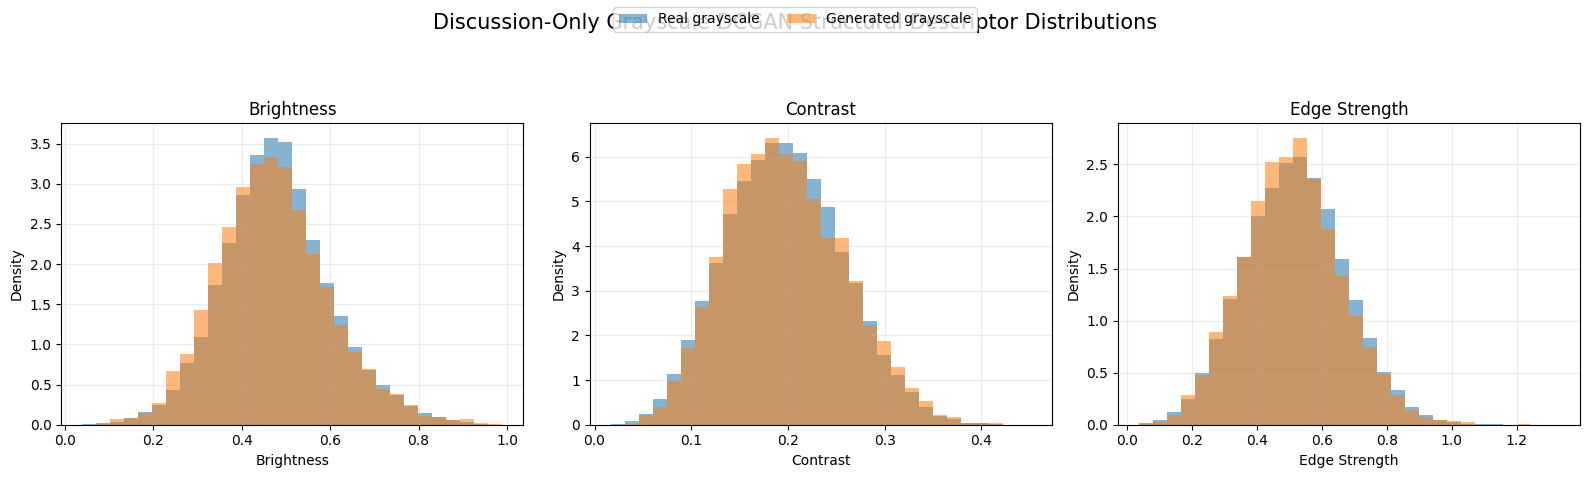

Grayscale structural descriptor distributions saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_structural_descriptor_distributions.png
Both real and generated histograms use density=True.
Protected test set remains unused.


In [72]:
GRAYSCALE_DESCRIPTOR_DISTRIBUTION_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "structural_descriptor_distributions.png"
    )
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
)


for axis, descriptor in zip(
    axes,
    GRAYSCALE_DESCRIPTOR_COLUMNS,
):
    real_values = (
        grayscale_real_descriptor_df[
            descriptor
        ].to_numpy(
            dtype=np.float64
        )
    )

    generated_values = (
        grayscale_generated_descriptor_df[
            descriptor
        ].to_numpy(
            dtype=np.float64
        )
    )


    assert np.isfinite(
        real_values
    ).all()

    assert np.isfinite(
        generated_values
    ).all()


    combined_minimum = float(
        min(
            real_values.min(),
            generated_values.min(),
        )
    )

    combined_maximum = float(
        max(
            real_values.max(),
            generated_values.max(),
        )
    )


    histogram_edges = np.linspace(
        combined_minimum,
        combined_maximum,
        31,
    )


    axis.hist(
        real_values,
        bins=histogram_edges,
        density=True,
        alpha=0.55,
        label="Real grayscale",
    )

    axis.hist(
        generated_values,
        bins=histogram_edges,
        density=True,
        alpha=0.55,
        label="Generated grayscale",
    )


    axis.set_title(
        descriptor
    )

    axis.set_xlabel(
        descriptor
    )

    axis.set_ylabel(
        "Density"
    )

    axis.grid(
        alpha=0.25
    )


handles, labels = (
    axes[0].get_legend_handles_labels()
)


figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)


figure.suptitle(
    (
        "Discussion-Only Grayscale DCGAN "
        "Structural Descriptor Distributions"
    ),
    fontsize=15,
)


figure.tight_layout(
    rect=(
        0.0,
        0.0,
        1.0,
        0.90,
    )
)


figure.savefig(
    GRAYSCALE_DESCRIPTOR_DISTRIBUTION_PATH,
    dpi=170,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


print(
    "Grayscale structural descriptor "
    "distributions saved:",
    GRAYSCALE_DESCRIPTOR_DISTRIBUTION_PATH,
)

print(
    "Both real and generated histograms "
    "use density=True."
)

print(
    "Protected test set remains unused."
)

### 14.13 Grayscale Structural Descriptor Findings

The selected grayscale DCGAN closely reproduced the low-level structural statistics of the grayscale CIFAR-10 training distribution.

| Descriptor | Real mean | Generated mean | Absolute difference | Generated-to-real SD ratio |
|---|---:|---:|---:|---:|
| Brightness | 0.4808 | 0.4723 | 0.0085 | 1.0404 |
| Contrast | 0.1962 | 0.1974 | 0.0012 | 1.0063 |
| Edge Strength | 0.5166 | 0.5098 | 0.0067 | 0.9773 |

Contrast was almost perfectly aligned in both mean and variation. Brightness was slightly lower for generated images, with mildly greater variation, while edge strength was slightly lower and marginally less variable than the real grayscale reference.

The density-normalised distributions substantially overlap for all three retained descriptors. There is no evidence of a severe brightness shift, contrast distortion or collapse of edge variation.

This is useful alongside the manual result of `40 Clear / 51 Marginal / 9 Nonsense`. The increase of `18` Clear images over the selected RGB unconditional GAN is therefore not accompanied by an obvious low-level statistical distortion. Instead, removing colour appears to have simplified the generation problem while preserving realistic grayscale luminance, contrast and edge characteristics.

These descriptors remain supporting evidence rather than a direct measure of semantic recognisability. They cannot by themselves prove that object structure improved.

The grayscale experiment remains discussion-only and is not eligible for final GAN selection.

### 14.14 Grayscale Diversity and Repetition

Improved structural recognisability would not be useful if the grayscale generator achieved it by producing a narrow set of repeated templates.

Feature-space diversity is therefore evaluated using the same cosine-distance framework used elsewhere in the GAN notebook.

The existing `5,000` generated grayscale images from seed `1302` are reused.

For uncertainty assessment, ten matched repeats are performed. Each repeat compares:

- `1,000` randomly sampled real grayscale CIFAR-10 images;
- `1,000` randomly sampled generated grayscale images.

Both real and generated grayscale images are replicated to three channels only for the frozen InceptionV3 feature extractor.

For each repeat, the analysis records:

- mean pairwise cosine distance;
- median pairwise cosine distance;
- median nearest-neighbour distance;
- minimum nearest-neighbour distance;
- generated-to-real diversity ratio;
- near-duplicate rate.

The near-duplicate threshold is defined independently within each repeat as the first percentile of nearest-neighbour distances among real grayscale images.

Exact duplicates are also checked across all `5,000` generated grayscale images.

This remains a generated-to-generated diversity and repetition analysis. No generated image is compared with the training set for memorisation; that audit remains reserved for Notebook 4.

In [74]:
required_grayscale_diversity_objects = [
    "GRAYSCALE_RUN_ID",
    "grayscale_real_rgb_uint8",
    "grayscale_descriptor_generated_uint8",
    "grayscale_descriptor_generated_rgb_uint8",
    "compact_cosine_diversity_summary",
    "extract_inception_features",
    "fid_feature_extractor",
    "FID_FEATURE_DIM",
    "FID_BATCH_SIZE",
    "DIVERSITY_SUBSET_SIZE",
    "DIVERSITY_REPEATS",
    "REAL_DIVERSITY_SEED",
    "GENERATED_DIVERSITY_SEED",
    "NEAR_DUPLICATE_PERCENTILE",
    "HISTORIES_DIR",
    "np",
    "pd",
]

missing_grayscale_diversity_objects = [
    name
    for name in required_grayscale_diversity_objects
    if name not in globals()
]

assert not missing_grayscale_diversity_objects, (
    "Incomplete grayscale diversity setup:\n"
    + "\n".join(
        missing_grayscale_diversity_objects
    )
)


assert grayscale_real_rgb_uint8.shape == (
    50_000,
    32,
    32,
    3,
)

assert grayscale_descriptor_generated_rgb_uint8.shape == (
    5_000,
    32,
    32,
    3,
)

assert grayscale_descriptor_generated_uint8.shape == (
    5_000,
    32,
    32,
    1,
)

assert DIVERSITY_SUBSET_SIZE == 1_000
assert DIVERSITY_REPEATS == 10

assert REAL_DIVERSITY_SEED == 1301
assert GENERATED_DIVERSITY_SEED == 1302

assert NEAR_DUPLICATE_PERCENTILE == 1.0


grayscale_generated_diversity_features = (
    extract_inception_features(
        images_uint8=(
            grayscale_descriptor_generated_rgb_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=FID_BATCH_SIZE,
    )
)


assert grayscale_generated_diversity_features.shape == (
    5_000,
    FID_FEATURE_DIM,
)

assert np.isfinite(
    grayscale_generated_diversity_features
).all()


print(
    "Grayscale generated diversity "
    "feature pool ready."
)

print(
    "Generated feature shape:",
    grayscale_generated_diversity_features.shape,
)

print(
    "Ten matched real/generated "
    "subsets will be evaluated next."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Grayscale generated diversity feature pool ready.
Generated feature shape: (5000, 2048)
Ten matched real/generated subsets will be evaluated next.
Protected test set remains unused.


In [75]:
grayscale_real_diversity_rng = (
    np.random.default_rng(
        REAL_DIVERSITY_SEED
    )
)

grayscale_generated_diversity_rng = (
    np.random.default_rng(
        GENERATED_DIVERSITY_SEED
    )
)


grayscale_diversity_repeat_rows = []

grayscale_diversity_representative = None


for repeat_index in range(
    1,
    DIVERSITY_REPEATS + 1,
):
    real_indices = (
        grayscale_real_diversity_rng.choice(
            len(grayscale_real_rgb_uint8),
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )

    generated_indices = (
        grayscale_generated_diversity_rng.choice(
            len(
                grayscale_generated_diversity_features
            ),
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )


    grayscale_real_repeat_features = (
        extract_inception_features(
            images_uint8=(
                grayscale_real_rgb_uint8[
                    real_indices
                ]
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=FID_BATCH_SIZE,
        )
    )


    assert grayscale_real_repeat_features.shape == (
        DIVERSITY_SUBSET_SIZE,
        FID_FEATURE_DIM,
    )


    real_summary = (
        compact_cosine_diversity_summary(
            grayscale_real_repeat_features
        )
    )

    generated_summary = (
        compact_cosine_diversity_summary(
            grayscale_generated_diversity_features[
                generated_indices
            ]
        )
    )


    near_duplicate_threshold = float(
        np.percentile(
            real_summary[
                "nearest_distances"
            ],
            NEAR_DUPLICATE_PERCENTILE,
        )
    )


    generated_near_duplicate_rate = float(
        np.mean(
            generated_summary[
                "nearest_distances"
            ]
            < near_duplicate_threshold
        )
        * 100.0
    )


    diversity_ratio = float(
        generated_summary[
            "mean_pairwise_distance"
        ]
        / real_summary[
            "mean_pairwise_distance"
        ]
    )


    grayscale_diversity_repeat_rows.append(
        {
            "Repeat": repeat_index,
            "Feature sample count": (
                DIVERSITY_SUBSET_SIZE
            ),
            "Real mean pairwise distance": (
                real_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "Generated mean pairwise distance": (
                generated_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "Generated median pairwise distance": (
                generated_summary[
                    "median_pairwise_distance"
                ]
            ),
            "Generated median nearest distance": (
                generated_summary[
                    "median_nearest_distance"
                ]
            ),
            "Generated minimum nearest distance": (
                generated_summary[
                    "minimum_nearest_distance"
                ]
            ),
            "Near-duplicate threshold": (
                near_duplicate_threshold
            ),
            "Near-duplicate rate (%)": (
                generated_near_duplicate_rate
            ),
            "Diversity ratio to real": (
                diversity_ratio
            ),
        }
    )


    if repeat_index == 1:
        grayscale_diversity_representative = {
            "generated_indices": (
                generated_indices.copy()
            ),
            "real_nearest_distances": (
                real_summary[
                    "nearest_distances"
                ].copy()
            ),
            "generated_nearest_distances": (
                generated_summary[
                    "nearest_distances"
                ].copy()
            ),
            "near_duplicate_threshold": (
                near_duplicate_threshold
            ),
        }


    print(
        f"Repeat {repeat_index:02d}/{DIVERSITY_REPEATS} "
        f"| diversity ratio: {diversity_ratio:.4f} "
        f"| near-duplicate rate: "
        f"{generated_near_duplicate_rate:.3f}%"
    )


grayscale_diversity_repeats_df = pd.DataFrame(
    grayscale_diversity_repeat_rows
)


assert len(
    grayscale_diversity_repeats_df
) == DIVERSITY_REPEATS

assert grayscale_diversity_representative is not None


print()

print(
    "Completed grayscale matched "
    "diversity repeats:",
    DIVERSITY_REPEATS,
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

Repeat 01/10 | diversity ratio: 0.8995 | near-duplicate rate: 0.000%


Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

Repeat 02/10 | diversity ratio: 0.8946 | near-duplicate rate: 0.000%


Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

...

Repeat 08/10 | diversity ratio: 0.9067 | near-duplicate rate: 0.500%


Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

Repeat 09/10 | diversity ratio: 0.9093 | near-duplicate rate: 0.000%


Extracting Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

Repeat 10/10 | diversity ratio: 0.9199 | near-duplicate rate: 0.400%

Completed grayscale matched diversity repeats: 10
Protected test set remains unused.


In [76]:
grayscale_diversity_summary_df = pd.DataFrame(
    [
        {
            "Run ID": GRAYSCALE_RUN_ID,
            "Repeat count": (
                DIVERSITY_REPEATS
            ),
            "Feature sample count per repeat": (
                DIVERSITY_SUBSET_SIZE
            ),
            "Real mean pairwise distance": float(
                grayscale_diversity_repeats_df[
                    "Real mean pairwise distance"
                ].mean()
            ),
            "Generated mean pairwise distance": float(
                grayscale_diversity_repeats_df[
                    "Generated mean pairwise distance"
                ].mean()
            ),
            "Generated median pairwise distance": float(
                grayscale_diversity_repeats_df[
                    "Generated median pairwise distance"
                ].mean()
            ),
            "Generated median nearest distance": float(
                grayscale_diversity_repeats_df[
                    "Generated median nearest distance"
                ].mean()
            ),
            "Generated minimum nearest distance": float(
                grayscale_diversity_repeats_df[
                    "Generated minimum nearest distance"
                ].mean()
            ),
            "Diversity ratio mean": float(
                grayscale_diversity_repeats_df[
                    "Diversity ratio to real"
                ].mean()
            ),
            "Diversity ratio SD": float(
                grayscale_diversity_repeats_df[
                    "Diversity ratio to real"
                ].std(ddof=1)
            ),
            "Near-duplicate rate mean (%)": float(
                grayscale_diversity_repeats_df[
                    "Near-duplicate rate (%)"
                ].mean()
            ),
            "Near-duplicate rate SD (%)": float(
                grayscale_diversity_repeats_df[
                    "Near-duplicate rate (%)"
                ].std(ddof=1)
            ),
        }
    ]
)


grayscale_flat_generated_images = (
    grayscale_descriptor_generated_uint8.reshape(
        5_000,
        -1,
    )
)


GRAYSCALE_UNIQUE_IMAGE_COUNT = int(
    np.unique(
        grayscale_flat_generated_images,
        axis=0,
    ).shape[0]
)

GRAYSCALE_EXACT_DUPLICATE_COUNT = int(
    5_000
    - GRAYSCALE_UNIQUE_IMAGE_COUNT
)

GRAYSCALE_EXACT_DUPLICATE_RATE = float(
    GRAYSCALE_EXACT_DUPLICATE_COUNT
    / 5_000
    * 100.0
)


grayscale_diversity_summary_df[
    "Image sample count"
] = 5_000

grayscale_diversity_summary_df[
    "Unique images"
] = GRAYSCALE_UNIQUE_IMAGE_COUNT

grayscale_diversity_summary_df[
    "Exact duplicates"
] = GRAYSCALE_EXACT_DUPLICATE_COUNT

grayscale_diversity_summary_df[
    "Exact-duplicate rate (%)"
] = GRAYSCALE_EXACT_DUPLICATE_RATE

grayscale_diversity_summary_df[
    "Discussion-only"
] = True

grayscale_diversity_summary_df[
    "Eligible for final GAN selection"
] = False


GRAYSCALE_DIVERSITY_REPEATS_PATH = (
    HISTORIES_DIR
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "diversity_repeats.csv"
    )
)

GRAYSCALE_DIVERSITY_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "diversity_summary.csv"
    )
)


grayscale_diversity_repeats_df.to_csv(
    GRAYSCALE_DIVERSITY_REPEATS_PATH,
    index=False,
)

grayscale_diversity_summary_df.to_csv(
    GRAYSCALE_DIVERSITY_SUMMARY_PATH,
    index=False,
)


display(
    grayscale_diversity_repeats_df.round(6)
)

display(
    grayscale_diversity_summary_df.round(6)
)


print(
    "Grayscale diversity ratio:",
    (
        f"{grayscale_diversity_summary_df['Diversity ratio mean'].iloc[0]:.6f}"
        " ± "
        f"{grayscale_diversity_summary_df['Diversity ratio SD'].iloc[0]:.6f}"
    ),
)

print(
    "Near-duplicate rate:",
    (
        f"{grayscale_diversity_summary_df['Near-duplicate rate mean (%)'].iloc[0]:.6f}"
        " ± "
        f"{grayscale_diversity_summary_df['Near-duplicate rate SD (%)'].iloc[0]:.6f}%"
    ),
)

print(
    "Exact duplicates:",
    GRAYSCALE_EXACT_DUPLICATE_COUNT,
)

print(
    "Exact-duplicate rate:",
    f"{GRAYSCALE_EXACT_DUPLICATE_RATE:.6f}%",
)

print(
    "Diversity results saved:",
    GRAYSCALE_DIVERSITY_SUMMARY_PATH,
)

print(
    "No generated-to-training memorisation "
    "audit was performed."
)

print(
    "Protected test set remains unused."
)

,Repeat,Feature sample count,Real mean pairwise distance,Generated mean pairwise distance,Generated median pairwise distance,Generated median nearest distance,Generated minimum nearest distance,Near-duplicate threshold,Near-duplicate rate (%),Diversity ratio to real
0,1,1000,0.320118,0.287947,0.285540,0.148551,0.091094,0.088073,0.0,0.899502
1,2,1000,0.324397,0.290218,0.287017,0.145406,0.086500,0.084453,0.0,0.894639
2,3,1000,0.318863,0.292548,0.289403,0.149114,0.090043,0.083214,0.0,0.917472
3,4,1000,0.320532,0.287676,0.284626,0.146867,0.083159,0.081857,0.0,0.897497
4,5,1000,0.315079,0.289775,0.286537,0.149527,0.071119,0.076818,0.2,0.919691
5,6,1000,0.317762,0.289653,0.286648,0.148249,0.080364,0.081197,0.2,0.911542
6,7,1000,0.319778,0.286872,0.283612,0.150063,0.082577,0.080768,0.0,0.897099
7,8,1000,0.323646,0.293440,0.291276,0.152309,0.078157,0.083966,0.5,0.906668
8,9,1000,0.320523,0.291459,0.289021,0.147877,0.079885,0.074477,0.0,0.909323
9,10,1000,0.316893,0.291495,0.289197,0.147384,0.082720,0.091026,0.4,0.919851


,Run ID,Repeat count,Feature sample count per repeat,Real mean pairwise distance,Generated mean pairwise distance,Generated median pairwise distance,Generated median nearest distance,Generated minimum nearest distance,Diversity ratio mean,Diversity ratio SD,Near-duplicate rate mean (%),Near-duplicate rate SD (%),Image sample count,Unique images,Exact duplicates,Exact-duplicate rate (%),Discussion-only,Eligible for final GAN selection
0,G12_grayscale_fliptranslation_seed42,10,1000,0.319759,0.290108,0.287288,0.148535,0.082562,0.907328,0.009765,0.13,0.188856,5000,5000,0,0.0,True,False


Grayscale diversity ratio: 0.907328 ± 0.009765
Near-duplicate rate: 0.130000 ± 0.188856%
Exact duplicates: 0
Exact-duplicate rate: 0.000000%
Diversity results saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_diversity_summary.csv
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


### 14.15 Grayscale Diversity Findings

The grayscale generator retained substantial feature-space diversity but showed a measurable reduction relative to the real grayscale distribution.

Across ten matched 1,000-image subsets, its generated-to-real diversity ratio was:

**0.9073 ± 0.0098**

The generated mean pairwise cosine distance was `0.2901`, compared with `0.3198` for real grayscale CIFAR-10 images. Generated samples therefore occupied a somewhat narrower feature-space distribution.

This reduction did not correspond to severe repetition. The mean near-duplicate rate was only `0.13%`, and all `5,000` generated images were pixel-wise unique, with zero exact duplicates.

For comparison, the selected RGB unconditional DCGAN previously achieved a higher diversity ratio of approximately `0.9522`. The grayscale model therefore appears to trade some visual variety for easier structural generation.

This complements the manual result of `40 Clear / 51 Marginal / 9 Nonsense`. Removing colour increased clearly recognisable structure by `18` images relative to the selected RGB unconditional GAN, while the present feature-space analysis shows that this improvement came with moderately compressed diversity rather than broad mode collapse.

The result therefore supports a trade-off rather than an unconditional improvement: grayscale simplifies the generative problem and improves structural recognisability, but reduces representational richness and removes useful colour information.

The experiment remains discussion-only and is not eligible for final GAN selection.

#### Grayscale Nearest-Neighbour Distance Distribution

The representative first diversity repeat is examined using an empirical cumulative distribution function of nearest-neighbour cosine distances.

The real and generated curves show whether the low overall near-duplicate percentage hides a broader shift toward more tightly clustered generated samples.

The vertical reference line is the first percentile of the real nearest-neighbour distances used as the near-duplicate threshold for this repeat.

This remains a generated-to-generated repetition analysis. It is not the generated-to-training memorisation audit reserved for Notebook 4.

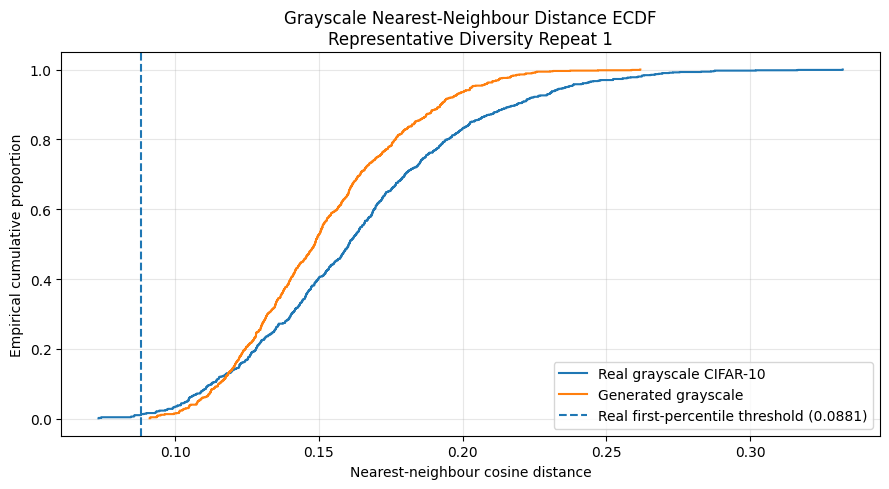

Representative real median nearest distance: 0.160400
Representative generated median nearest distance: 0.148551
Representative near-duplicate threshold: 0.088073
ECDF saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_nearest_distance_ecdf.png
No generated-to-training memorisation audit was performed.
Protected test set remains unused.


In [78]:
required_grayscale_ecdf_objects = [
    "GRAYSCALE_RUN_ID",
    "grayscale_diversity_representative",
    "GRIDS_DIR",
    "np",
    "plt",
    "Path",
]

missing_grayscale_ecdf_objects = [
    name
    for name in required_grayscale_ecdf_objects
    if name not in globals()
]

assert not missing_grayscale_ecdf_objects, (
    "Incomplete grayscale ECDF setup:\n"
    + "\n".join(
        missing_grayscale_ecdf_objects
    )
)


grayscale_real_nearest_distances = np.asarray(
    grayscale_diversity_representative[
        "real_nearest_distances"
    ],
    dtype=np.float64,
)

grayscale_generated_nearest_distances = np.asarray(
    grayscale_diversity_representative[
        "generated_nearest_distances"
    ],
    dtype=np.float64,
)

grayscale_representative_threshold = float(
    grayscale_diversity_representative[
        "near_duplicate_threshold"
    ]
)


assert grayscale_real_nearest_distances.shape == (
    DIVERSITY_SUBSET_SIZE,
)

assert grayscale_generated_nearest_distances.shape == (
    DIVERSITY_SUBSET_SIZE,
)

assert np.isfinite(
    grayscale_real_nearest_distances
).all()

assert np.isfinite(
    grayscale_generated_nearest_distances
).all()


grayscale_real_sorted_distances = np.sort(
    grayscale_real_nearest_distances
)

grayscale_generated_sorted_distances = np.sort(
    grayscale_generated_nearest_distances
)


grayscale_real_ecdf = np.arange(
    1,
    DIVERSITY_SUBSET_SIZE + 1,
    dtype=np.float64,
) / DIVERSITY_SUBSET_SIZE

grayscale_generated_ecdf = np.arange(
    1,
    DIVERSITY_SUBSET_SIZE + 1,
    dtype=np.float64,
) / DIVERSITY_SUBSET_SIZE


GRAYSCALE_NEAREST_DISTANCE_ECDF_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "nearest_distance_ecdf.png"
    )
)


plt.figure(
    figsize=(9, 5)
)

plt.step(
    grayscale_real_sorted_distances,
    grayscale_real_ecdf,
    where="post",
    label="Real grayscale CIFAR-10",
)

plt.step(
    grayscale_generated_sorted_distances,
    grayscale_generated_ecdf,
    where="post",
    label="Generated grayscale",
)

plt.axvline(
    grayscale_representative_threshold,
    linestyle="--",
    label=(
        "Real first-percentile threshold "
        f"({grayscale_representative_threshold:.4f})"
    ),
)

plt.xlabel(
    "Nearest-neighbour cosine distance"
)

plt.ylabel(
    "Empirical cumulative proportion"
)

plt.title(
    "Grayscale Nearest-Neighbour Distance ECDF\n"
    "Representative Diversity Repeat 1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    GRAYSCALE_NEAREST_DISTANCE_ECDF_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Representative real median nearest distance:",
    f"{np.median(grayscale_real_nearest_distances):.6f}",
)

print(
    "Representative generated median nearest distance:",
    f"{np.median(grayscale_generated_nearest_distances):.6f}",
)

print(
    "Representative near-duplicate threshold:",
    f"{grayscale_representative_threshold:.6f}",
)

print(
    "ECDF saved:",
    GRAYSCALE_NEAREST_DISTANCE_ECDF_PATH,
)

print(
    "No generated-to-training memorisation "
    "audit was performed."
)

print(
    "Protected test set remains unused."
)

#### Closest Grayscale Generated Pairs

The eight closest feature-space pairs from the representative 1,000-image generated subset are displayed.

This provides a visual check on what the smallest cosine distances represent.

Similar subject matter, pose or background does not by itself constitute mode collapse. The relevant question is whether the closest samples are effectively duplicated images or whether meaningful visual differences remain.

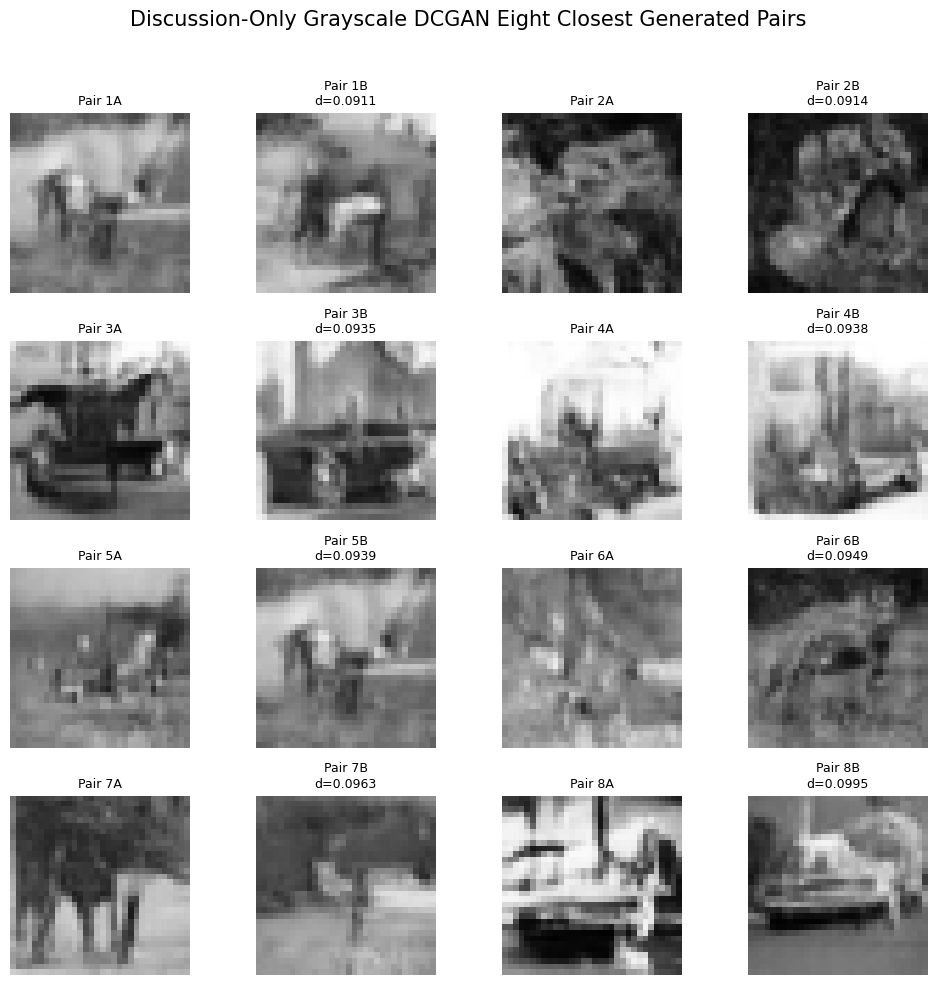

,Pair rank,Cosine distance,First pool index,Second pool index
0,1,0.091094,2064,3610
1,2,0.091390,4287,2772
2,3,0.093549,3714,796
3,4,0.093754,1533,4502
4,5,0.093923,2902,2064
5,6,0.094930,52,4057
6,7,0.096339,977,1327
7,8,0.099531,316,2943


Closest-pair table saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_closest_generated_pairs.csv
Closest-pair figure saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_closest_generated_pairs.png
Exact duplicates in the full 5,000-image pool: 0
Protected test set remains unused.


In [79]:
from sklearn.metrics.pairwise import cosine_distances


required_grayscale_closest_pair_objects = [
    "GRAYSCALE_RUN_ID",
    "grayscale_diversity_representative",
    "grayscale_generated_diversity_features",
    "grayscale_descriptor_generated_uint8",
    "GRIDS_DIR",
    "HISTORIES_DIR",
    "np",
    "pd",
    "plt",
    "Path",
]

missing_grayscale_closest_pair_objects = [
    name
    for name in required_grayscale_closest_pair_objects
    if name not in globals()
]

assert not missing_grayscale_closest_pair_objects, (
    "Incomplete grayscale closest-pair setup:\n"
    + "\n".join(
        missing_grayscale_closest_pair_objects
    )
)


GRAYSCALE_CLOSEST_PAIR_COUNT = 8


grayscale_representative_generated_indices = np.asarray(
    grayscale_diversity_representative[
        "generated_indices"
    ],
    dtype=np.int64,
)


assert grayscale_representative_generated_indices.shape == (
    DIVERSITY_SUBSET_SIZE,
)


grayscale_representative_generated_features = (
    grayscale_generated_diversity_features[
        grayscale_representative_generated_indices
    ]
)


assert grayscale_representative_generated_features.shape == (
    DIVERSITY_SUBSET_SIZE,
    FID_FEATURE_DIM,
)


grayscale_pairwise_distance_matrix = (
    cosine_distances(
        grayscale_representative_generated_features
    )
)


assert grayscale_pairwise_distance_matrix.shape == (
    DIVERSITY_SUBSET_SIZE,
    DIVERSITY_SUBSET_SIZE,
)

assert np.isfinite(
    grayscale_pairwise_distance_matrix
).all()


upper_row_indices, upper_column_indices = (
    np.triu_indices(
        DIVERSITY_SUBSET_SIZE,
        k=1,
    )
)


upper_pair_distances = (
    grayscale_pairwise_distance_matrix[
        upper_row_indices,
        upper_column_indices,
    ]
)


closest_pair_order = np.argsort(
    upper_pair_distances
)[
    :GRAYSCALE_CLOSEST_PAIR_COUNT
]


grayscale_closest_pair_rows = []


for pair_rank, pair_position in enumerate(
    closest_pair_order,
    start=1,
):
    first_subset_index = int(
        upper_row_indices[
            pair_position
        ]
    )

    second_subset_index = int(
        upper_column_indices[
            pair_position
        ]
    )

    first_pool_index = int(
        grayscale_representative_generated_indices[
            first_subset_index
        ]
    )

    second_pool_index = int(
        grayscale_representative_generated_indices[
            second_subset_index
        ]
    )

    pair_distance = float(
        upper_pair_distances[
            pair_position
        ]
    )


    grayscale_closest_pair_rows.append(
        {
            "Pair rank": pair_rank,
            "Cosine distance": pair_distance,
            "First pool index": (
                first_pool_index
            ),
            "Second pool index": (
                second_pool_index
            ),
        }
    )


grayscale_closest_pairs_df = pd.DataFrame(
    grayscale_closest_pair_rows
)


assert len(
    grayscale_closest_pairs_df
) == GRAYSCALE_CLOSEST_PAIR_COUNT


GRAYSCALE_CLOSEST_PAIRS_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "closest_generated_pairs.csv"
    )
)

GRAYSCALE_CLOSEST_PAIRS_FIGURE_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "closest_generated_pairs.png"
    )
)


grayscale_closest_pairs_df.to_csv(
    GRAYSCALE_CLOSEST_PAIRS_PATH,
    index=False,
)


figure, axes = plt.subplots(
    4,
    4,
    figsize=(10, 10),
)


for pair_index, row in (
    grayscale_closest_pairs_df.iterrows()
):
    figure_row = (
        pair_index // 2
    )

    figure_column = (
        pair_index % 2
    ) * 2


    first_pool_index = int(
        row[
            "First pool index"
        ]
    )

    second_pool_index = int(
        row[
            "Second pool index"
        ]
    )

    pair_distance = float(
        row[
            "Cosine distance"
        ]
    )


    axes[
        figure_row,
        figure_column,
    ].imshow(
        grayscale_descriptor_generated_uint8[
            first_pool_index,
            :,
            :,
            0,
        ],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        figure_row,
        figure_column,
    ].set_title(
        f"Pair {pair_index + 1}A",
        fontsize=9,
    )

    axes[
        figure_row,
        figure_column,
    ].axis("off")


    axes[
        figure_row,
        figure_column + 1,
    ].imshow(
        grayscale_descriptor_generated_uint8[
            second_pool_index,
            :,
            :,
            0,
        ],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        figure_row,
        figure_column + 1,
    ].set_title(
        (
            f"Pair {pair_index + 1}B\n"
            f"d={pair_distance:.4f}"
        ),
        fontsize=9,
    )

    axes[
        figure_row,
        figure_column + 1,
    ].axis("off")


figure.suptitle(
    (
        "Discussion-Only Grayscale DCGAN "
        "Eight Closest Generated Pairs"
    ),
    fontsize=15,
)

figure.tight_layout(
    rect=(
        0.0,
        0.0,
        1.0,
        0.96,
    )
)

figure.savefig(
    GRAYSCALE_CLOSEST_PAIRS_FIGURE_PATH,
    dpi=170,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


display(
    grayscale_closest_pairs_df.round(6)
)


print(
    "Closest-pair table saved:",
    GRAYSCALE_CLOSEST_PAIRS_PATH,
)

print(
    "Closest-pair figure saved:",
    GRAYSCALE_CLOSEST_PAIRS_FIGURE_PATH,
)

print(
    "Exact duplicates in the full "
    "5,000-image pool:",
    GRAYSCALE_EXACT_DUPLICATE_COUNT,
)

print(
    "Protected test set remains unused."
)

### 14.16 Direct RGB-versus-Grayscale Structural Comparison

A final qualitative comparison examines the selected RGB unconditional DCGAN and the discussion-only grayscale DCGAN directly.

Both generators receive the same fixed latent vectors. Because the two networks were trained independently, the same latent vector is not expected to represent the same semantic object in both models. The matched inputs instead provide a reproducible, uncurated comparison of the structures produced by each generator under an identical latent sample set.

For each latent vector, three views are displayed:

1. the selected RGB unconditional GAN output;
2. that same RGB output converted to grayscale for a structure-only view;
3. the native grayscale GAN output.

The middle column helps separate two effects:

- simply removing colour from an RGB-generated image;
- training the GAN itself on the reduced one-channel grayscale problem.

The comparison is interpreted together with the formal manual scores, descriptor alignment and diversity evidence rather than from individual examples alone.

The grayscale model remains discussion-only and cannot become the final GAN.

In [82]:
required_grayscale_rgb_visual_objects = [
    "build_dcgan_generator",
    "grayscale_reloaded_generator",
    "make_stateless_noise",
    "WEIGHTS_DIR",
    "GRIDS_DIR",
    "np",
    "tf",
    "plt",
    "Path",
]

missing_grayscale_rgb_visual_objects = [
    name
    for name
    in required_grayscale_rgb_visual_objects
    if name not in globals()
]

assert not missing_grayscale_rgb_visual_objects, (
    "Incomplete RGB-versus-grayscale "
    "visual-comparison setup:\n"
    + "\n".join(
        missing_grayscale_rgb_visual_objects
    )
)


RGB_STRUCTURAL_COMPARISON_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

RGB_STRUCTURAL_COMPARISON_EPOCH = 100

GRAYSCALE_RGB_VISUAL_SEED = 1701

GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT = 10

GRAYSCALE_RGB_VISUAL_LATENT_DIM = 100


RGB_STRUCTURAL_COMPARISON_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{RGB_STRUCTURAL_COMPARISON_RUN_ID}_"
        f"epoch{RGB_STRUCTURAL_COMPARISON_EPOCH:03d}_"
        "generator.weights.h5"
    )
)


assert (
    RGB_STRUCTURAL_COMPARISON_GENERATOR_PATH
    .is_file()
), (
    "Missing selected RGB generator weights:\n"
    f"{RGB_STRUCTURAL_COMPARISON_GENERATOR_PATH}"
)


rgb_structural_comparison_generator = (
    build_dcgan_generator(
        GRAYSCALE_RGB_VISUAL_LATENT_DIM
    )
)


assert int(
    rgb_structural_comparison_generator.count_params()
) == 1_085_187


rgb_structural_comparison_generator.load_weights(
    RGB_STRUCTURAL_COMPARISON_GENERATOR_PATH
)


grayscale_rgb_visual_noise = (
    make_stateless_noise(
        sample_count=(
            GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT
        ),
        latent_dim=(
            GRAYSCALE_RGB_VISUAL_LATENT_DIM
        ),
        seed=(
            GRAYSCALE_RGB_VISUAL_SEED
        ),
    )
)


rgb_structural_outputs = (
    rgb_structural_comparison_generator(
        grayscale_rgb_visual_noise,
        training=False,
    )
    .numpy()
)

grayscale_structural_outputs = (
    grayscale_reloaded_generator(
        grayscale_rgb_visual_noise,
        training=False,
    )
    .numpy()
)


assert rgb_structural_outputs.shape == (
    GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT,
    32,
    32,
    3,
)

assert grayscale_structural_outputs.shape == (
    GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT,
    32,
    32,
    1,
)

assert np.isfinite(
    rgb_structural_outputs
).all()

assert np.isfinite(
    grayscale_structural_outputs
).all()


rgb_structural_images = np.clip(
    (
        rgb_structural_outputs
        + 1.0
    )
    / 2.0,
    0.0,
    1.0,
)

grayscale_structural_images = np.clip(
    (
        grayscale_structural_outputs
        + 1.0
    )
    / 2.0,
    0.0,
    1.0,
)


rgb_outputs_as_grayscale = (
    tf.image.rgb_to_grayscale(
        tf.convert_to_tensor(
            rgb_structural_images,
            dtype=tf.float32,
        )
    )
    .numpy()
)


GRAYSCALE_RGB_STRUCTURAL_COMPARISON_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "vs_rgb_structural_comparison.png"
    )
)


figure, axes = plt.subplots(
    GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT,
    3,
    figsize=(8, 24),
    squeeze=False,
)


for image_index in range(
    GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT
):
    axes[
        image_index,
        0,
    ].imshow(
        rgb_structural_images[
            image_index
        ]
    )

    axes[
        image_index,
        1,
    ].imshow(
        rgb_outputs_as_grayscale[
            image_index,
            :,
            :,
            0,
        ],
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )

    axes[
        image_index,
        2,
    ].imshow(
        grayscale_structural_images[
            image_index,
            :,
            :,
            0,
        ],
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )


    axes[
        image_index,
        0,
    ].set_ylabel(
        f"Noise {image_index + 1}",
        rotation=0,
        labelpad=30,
        va="center",
    )


    for column_index in range(3):
        axes[
            image_index,
            column_index,
        ].axis("off")


axes[0, 0].set_title(
    "RGB GAN",
    fontsize=12,
)

axes[0, 1].set_title(
    "RGB GAN\nconverted to grayscale",
    fontsize=12,
)

axes[0, 2].set_title(
    "Native grayscale GAN",
    fontsize=12,
)


figure.suptitle(
    (
        "Selected RGB versus Discussion-Only "
        "Grayscale DCGAN\n"
        "Matched Latent Inputs, "
        "No Curation"
    ),
    fontsize=16,
)


figure.tight_layout(
    rect=(0.05, 0.0, 1.0, 0.975)
)


figure.savefig(
    GRAYSCALE_RGB_STRUCTURAL_COMPARISON_PATH,
    dpi=180,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


print(
    "RGB-versus-grayscale structural "
    "comparison saved:",
    GRAYSCALE_RGB_STRUCTURAL_COMPARISON_PATH,
)

print(
    "Matched latent seed:",
    GRAYSCALE_RGB_VISUAL_SEED,
)

print(
    "Displayed latent vectors:",
    GRAYSCALE_RGB_VISUAL_SAMPLE_COUNT,
)

print(
    "No filtering, rejection sampling "
    "or manual curation was applied."
)

print(
    "Same latent vectors do not imply "
    "semantic correspondence because the "
    "generators were trained independently."
)

print(
    "The grayscale model remains "
    "discussion-only."
)

print(
    "Protected test set remains unused."
)

RGB-versus-grayscale structural comparison saved: [local project directory]/grids/G12_grayscale_fliptranslation_seed42_vs_rgb_structural_comparison.png
Matched latent seed: 1701
Displayed latent vectors: 10
No filtering, rejection sampling or manual curation was applied.
Same latent vectors do not imply semantic correspondence because the generators were trained independently.
The grayscale model remains discussion-only.
Protected test set remains unused.


### 14.17 Grayscale Discussion Conclusion

The grayscale experiment asked:

> Does reducing channel complexity improve structural generation enough to compensate for losing useful CIFAR-10 colour information?

Under the retained DCGAN architecture and training settings, **grayscale generation was easier in terms of structural recognisability, but it was not better overall**.

The strongest evidence came from the strict 100-image manual assessment. The grayscale GAN produced:

- **40 Clear**
- **51 Marginal**
- **9 Nonsense**

compared with:

- **22 Clear**
- **70 Marginal**
- **8 Nonsense**

for the selected RGB unconditional DCGAN.

The increase of `18` Clear images exceeds the approximate manual-resolution threshold of `13`. Removing colour therefore produced a meaningful improvement in clearly recognisable structure rather than a practical tie.

The structural descriptor evidence supports this result without indicating a major low-level distortion. Generated grayscale images closely matched the real grayscale training distribution in brightness, contrast and edge strength. Their absolute mean differences were only `0.0085`, `0.0012` and `0.0067`, respectively, and the density-normalised distributions showed substantial overlap.

The improvement did not result from severe repetition or mode collapse. Across ten matched feature-space subsets, the grayscale GAN achieved a generated-to-real diversity ratio of:

**0.9073 ± 0.0098**

with a near-duplicate rate of only approximately `0.13%` and zero exact duplicates among `5,000` generated images.

However, the grayscale diversity ratio was lower than the approximately `0.9522` achieved by the selected RGB unconditional GAN. The nearest-neighbour ECDF also showed generated grayscale samples tending to have closer neighbours than real grayscale images. Grayscale therefore produced a somewhat narrower range of appearances even though it did not collapse.

The direct matched-latent visual comparison was consistent with this trade-off. Native grayscale generation sometimes produced strong, high-contrast object silhouettes, but it was not uniformly superior to the RGB model on every latent input. Because the two generators were trained independently, matched latent vectors were used only to provide a reproducible uncurated visual comparison and were not interpreted as semantic pairs.

The selected grayscale checkpoint achieved repeated grayscale-reference FID of:

**22.0720 ± 0.1403**

This value demonstrates stable agreement with the grayscale-transformed CIFAR-10 distribution, but it must not be ranked directly against RGB FID because the real reference distributions are different.

Overall, reducing the image from three colour channels to one appears to simplify the structural generation problem for this DCGAN. The model produced substantially more clearly recognisable shapes while retaining realistic grayscale brightness, contrast and edge statistics.

The simplification nevertheless removes useful colour cues and moderately compresses feature-space diversity. Therefore, the structural improvement does **not** justify replacing the RGB task with grayscale generation.

The grayscale model remains a **discussion-only sensitivity experiment**. It is not eligible for final GAN selection and no grayscale hyperparameter tuning or second training seed will be performed.

In [88]:
GRAYSCALE_RUN_ID = (
    "G12_grayscale_fliptranslation_seed42"
)

GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD = 13


# Use the existing notebook directory if available.
# Otherwise fall back to the standard project Drive path.
grayscale_histories_dir = Path(
    globals().get(
        "HISTORIES_DIR",
        "[local project directory]/histories",
    )
)


grayscale_saved_paths = {
    "artifact_audit": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "artifact_audit.csv"
        )
    ),
    "checkpoint_selection": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "checkpoint_selection.csv"
        )
    ),
    "repeated_fid": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "repeated_grayscale_reference_fid_summary.csv"
        )
    ),
    "manual_summary": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "manual_quality_summary.csv"
        )
    ),
    "manual_rgb_comparison": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "vs_rgb_manual_structural_comparison.csv"
        )
    ),
    "descriptor_comparison": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "structural_descriptor_comparison.csv"
        )
    ),
    "diversity_summary": (
        grayscale_histories_dir
        / (
            f"{GRAYSCALE_RUN_ID}_"
            "diversity_summary.csv"
        )
    ),
}


for artifact_name, artifact_path in (
    grayscale_saved_paths.items()
):
    assert artifact_path.is_file(), (
        f"Missing grayscale artifact "
        f"{artifact_name}:\n"
        f"{artifact_path}"
    )


grayscale_artifact_audit_df = pd.read_csv(
    grayscale_saved_paths[
        "artifact_audit"
    ]
)

grayscale_checkpoint_selection_df = pd.read_csv(
    grayscale_saved_paths[
        "checkpoint_selection"
    ]
)

grayscale_repeated_fid_summary_df = pd.read_csv(
    grayscale_saved_paths[
        "repeated_fid"
    ]
)

grayscale_manual_summary_df = pd.read_csv(
    grayscale_saved_paths[
        "manual_summary"
    ]
)

grayscale_vs_rgb_manual_comparison_df = pd.read_csv(
    grayscale_saved_paths[
        "manual_rgb_comparison"
    ]
)

grayscale_descriptor_comparison_df = pd.read_csv(
    grayscale_saved_paths[
        "descriptor_comparison"
    ]
)

grayscale_diversity_summary_df = pd.read_csv(
    grayscale_saved_paths[
        "diversity_summary"
    ]
)


# ---------------------------------------------------------
# Validate one-row summary artifacts
# ---------------------------------------------------------

for summary_df in [
    grayscale_artifact_audit_df,
    grayscale_checkpoint_selection_df,
    grayscale_repeated_fid_summary_df,
    grayscale_manual_summary_df,
    grayscale_diversity_summary_df,
]:
    assert len(summary_df) == 1


artifact_row = (
    grayscale_artifact_audit_df.iloc[0]
)

selection_row = (
    grayscale_checkpoint_selection_df.iloc[0]
)

fid_row = (
    grayscale_repeated_fid_summary_df.iloc[0]
)

manual_row = (
    grayscale_manual_summary_df.iloc[0]
)

diversity_row = (
    grayscale_diversity_summary_df.iloc[0]
)


# Manual RGB comparison

assert len(
    grayscale_vs_rgb_manual_comparison_df
) == 2


rgb_manual_row = (
    grayscale_vs_rgb_manual_comparison_df.loc[
        grayscale_vs_rgb_manual_comparison_df[
            "Run ID"
        ]
        == "G08_augmentation_fliptranslation_seed42"
    ]
    .iloc[0]
)

grayscale_manual_comparison_row = (
    grayscale_vs_rgb_manual_comparison_df.loc[
        grayscale_vs_rgb_manual_comparison_df[
            "Run ID"
        ]
        == GRAYSCALE_RUN_ID
    ]
    .iloc[0]
)


grayscale_clear_difference = int(
    grayscale_manual_comparison_row[
        "Clear"
    ]
    - rgb_manual_row[
        "Clear"
    ]
)


# Descriptor values

grayscale_descriptor_lookup = (
    grayscale_descriptor_comparison_df
    .set_index("Descriptor")
)


for required_descriptor in [
    "Brightness",
    "Contrast",
    "Edge Strength",
]:
    assert (
        required_descriptor
        in grayscale_descriptor_lookup.index
    )


brightness_error = float(
    grayscale_descriptor_lookup.loc[
        "Brightness",
        "Absolute Mean Difference",
    ]
)

contrast_error = float(
    grayscale_descriptor_lookup.loc[
        "Contrast",
        "Absolute Mean Difference",
    ]
)

edge_error = float(
    grayscale_descriptor_lookup.loc[
        "Edge Strength",
        "Absolute Mean Difference",
    ]
)


# Pull final values directly from saved artifacts

selected_epoch = int(
    selection_row[
        "Selected epoch"
    ]
)

selected_milestone_fid = float(
    selection_row[
        "Selected grayscale-reference FID"
    ]
)

repeated_fid_mean = float(
    fid_row[
        "Repeated grayscale-reference FID mean"
    ]
)

repeated_fid_sd = float(
    fid_row[
        "Repeated grayscale-reference FID SD"
    ]
)

training_time_minutes = float(
    artifact_row[
        "Training time minutes"
    ]
)

clear_count = int(
    manual_row[
        "Clear"
    ]
)

marginal_count = int(
    manual_row[
        "Marginal"
    ]
)

nonsense_count = int(
    manual_row[
        "Nonsense"
    ]
)

diversity_ratio_mean = float(
    diversity_row[
        "Diversity ratio mean"
    ]
)

diversity_ratio_sd = float(
    diversity_row[
        "Diversity ratio SD"
    ]
)

near_duplicate_rate = float(
    diversity_row[
        "Near-duplicate rate mean (%)"
    ]
)

exact_duplicates = int(
    diversity_row[
        "Exact duplicates"
    ]
)


# Sanity checks

assert selected_epoch == 100

assert (
    clear_count
    + marginal_count
    + nonsense_count
    == 100
)

assert grayscale_clear_difference == 18

assert (
    grayscale_clear_difference
    >= GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD
)

assert exact_duplicates == 0

assert np.isfinite(
    [
        selected_milestone_fid,
        repeated_fid_mean,
        repeated_fid_sd,
        training_time_minutes,
        brightness_error,
        contrast_error,
        edge_error,
        diversity_ratio_mean,
        diversity_ratio_sd,
        near_duplicate_rate,
    ]
).all()


# ---------------------------------------------------------
# Final discussion summary
# ---------------------------------------------------------

grayscale_discussion_summary_df = pd.DataFrame(
    [
        {
            "Run ID": (
                GRAYSCALE_RUN_ID
            ),
            "Selected epoch": (
                selected_epoch
            ),
            "Selected milestone grayscale-reference FID": (
                selected_milestone_fid
            ),
            "Repeated grayscale-reference FID mean": (
                repeated_fid_mean
            ),
            "Repeated grayscale-reference FID SD": (
                repeated_fid_sd
            ),
            "Clear": (
                clear_count
            ),
            "Marginal": (
                marginal_count
            ),
            "Nonsense": (
                nonsense_count
            ),
            "Clear difference vs RGB": (
                grayscale_clear_difference
            ),
            "Manual threshold": (
                GRAYSCALE_MANUAL_RESOLUTION_THRESHOLD
            ),
            "Brightness absolute mean error": (
                brightness_error
            ),
            "Contrast absolute mean error": (
                contrast_error
            ),
            "Edge-strength absolute mean error": (
                edge_error
            ),
            "Diversity ratio mean": (
                diversity_ratio_mean
            ),
            "Diversity ratio SD": (
                diversity_ratio_sd
            ),
            "Near-duplicate rate mean (%)": (
                near_duplicate_rate
            ),
            "Exact duplicates": (
                exact_duplicates
            ),
            "Training time minutes": (
                training_time_minutes
            ),
            "Structural generation easier": True,
            "Compensates for colour loss overall": False,
            "Eligible for final GAN selection": False,
            "Decision": (
                "Grayscale improved structural "
                "recognisability, but removed useful "
                "colour information and reduced "
                "feature-space diversity. "
                "Discussion-only."
            ),
        }
    ]
)


GRAYSCALE_DISCUSSION_SUMMARY_PATH = (
    grayscale_histories_dir
    / (
        f"{GRAYSCALE_RUN_ID}_"
        "discussion_conclusion.csv"
    )
)


grayscale_discussion_summary_df.to_csv(
    GRAYSCALE_DISCUSSION_SUMMARY_PATH,
    index=False,
)


display(
    grayscale_discussion_summary_df.round(6)
)


print(
    "Grayscale research question answered."
)

print(
    "Selected milestone grayscale-reference FID:",
    f"{selected_milestone_fid:.4f}",
)

print(
    "Repeated grayscale-reference FID:",
    (
        f"{repeated_fid_mean:.4f}"
        " ± "
        f"{repeated_fid_sd:.4f}"
    ),
)

print(
    "Manual result:",
    (
        f"{clear_count} Clear / "
        f"{marginal_count} Marginal / "
        f"{nonsense_count} Nonsense"
    ),
)

print(
    "Clear difference vs RGB:",
    f"{grayscale_clear_difference:+d}",
)

print(
    "Diversity ratio:",
    (
        f"{diversity_ratio_mean:.6f}"
        " ± "
        f"{diversity_ratio_sd:.6f}"
    ),
)

print(
    "Training time:",
    f"{training_time_minutes:.4f}",
    "minutes",
)

print(
    "Structural generation easier:",
    True,
)

print(
    "Compensates for colour loss overall:",
    False,
)

print(
    "Eligible for final GAN selection:",
    False,
)

print(
    "Grayscale experiment closed."
)

print(
    "Summary saved:",
    GRAYSCALE_DISCUSSION_SUMMARY_PATH,
)

print(
    "Protected test set remains unused."
)

,Run ID,Selected epoch,Selected milestone grayscale-reference FID,Repeated grayscale-reference FID mean,Repeated grayscale-reference FID SD,Clear,Marginal,Nonsense,Clear difference vs RGB,Manual threshold,...,Edge-strength absolute mean error,Diversity ratio mean,Diversity ratio SD,Near-duplicate rate mean (%),Exact duplicates,Training time minutes,Structural generation easier,Compensates for colour loss overall,Eligible for final GAN selection,Decision
0,G12_grayscale_fliptranslation_seed42,100,21.838227,22.072012,0.140342,40,51,9,18,13,...,0.006732,0.907328,0.009765,0.13,0,21.680102,True,False,False,"Grayscale improved structural recognisability,..."


Grayscale research question answered.
Selected milestone grayscale-reference FID: 21.8382
Repeated grayscale-reference FID: 22.0720 ± 0.1403
Manual result: 40 Clear / 51 Marginal / 9 Nonsense
Clear difference vs RGB: +18
Diversity ratio: 0.907328 ± 0.009765
Training time: 21.6801 minutes
Structural generation easier: True
Compensates for colour loss overall: False
Eligible for final GAN selection: False
Grayscale experiment closed.
Summary saved: [local project directory]/histories/G12_grayscale_fliptranslation_seed42_discussion_conclusion.csv
Protected test set remains unused.


---

## 15. Focused Conditional Augmentation Ablation

The earlier unconditional augmentation family already established that horizontal flip plus mild translation was a defensible pragmatic choice, but its advantage was modest and sensitive to independent training seeds.

That evidence does **not** answer whether augmentation remains useful after class conditioning is introduced. Every completed conditional finalist so far used flip plus translation.

This section therefore asks a new controlled question:

> **Does horizontal flip plus two-pixel translation augmentation still provide useful benefit once class conditioning is introduced?**

The reference is:

`G10_conditional_fliptranslation_seed42`

The fresh ablation is:

`G13_conditional_noaugmentation_seed42`

The ablation removes **only discriminator-side augmentation**.

Everything else is held fixed:

- the same conditional generator architecture;
- the same conditional discriminator architecture;
- label embedding dimension `50`;
- latent dimension `100`;
- all `50,000` CIFAR-10 training images;
- balanced training labels;
- batch size `64`;
- generator learning rate `2e-4`;
- discriminator learning rate `2e-4`;
- Adam `beta_1 = 0.5`, `beta_2 = 0.999`;
- one discriminator update per generator update;
- training seed `42`;
- `100` epochs;
- `782` batches per epoch;
- `78,200` updates per network;
- milestone checkpoints at epochs `50`, `70`, `90` and `100`;
- the same fixed-grid and FID evaluation protocols.

G13 therefore differs from G10 in one intentional modelling factor only:

**flip + translation augmentation → no augmentation**

### Confirmation rule

A single seed will not be allowed to replace the conditional finalist.

After G13's selected checkpoint receives repeated FID:

- if G13 is **at least 2.0 FID worse** than G10 at seed `42`, the ablation has failed clearly enough to retain the already two-seed-supported augmented reference and no confirmation run is required;
- if G13 is **within 2.0 FID** of G10, the result is unresolved and seed `123` confirmation is required;
- if G13 is **at least 2.0 FID better** than G10, seed `123` confirmation is required before augmentation can be rejected.

The confirmation run, if triggered, will be:

`G14_conditional_noaugmentation_seed123`

The final augmentation decision will then compare the two training-seed means:

- augmented: `G10` seed `42` + `G11` seed `123`;
- unaugmented: `G13` seed `42` + `G14` seed `123`.

For the predeclared `2 vs 2` comparison:

- practical FID margin = `2.0000`;
- baseline difference SD = `0.4256`;
- approximate 80% detectable effect = `2.3575`.

Single-seed manual, adherence, coverage or diversity evidence will not be used to decide an otherwise unresolved tie.

No broader conditional augmentation sweep will follow this ablation.

In [ ]:
required_ablation_contract_objects = [
    "np",
    "pd",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "CURRENT_LATENT_DIM",
    "CURRENT_BATCH_SIZE",
    "CURRENT_EPOCHS",
    "CURRENT_GENERATOR_LR",
    "CURRENT_DISCRIMINATOR_LR",
    "CURRENT_BETA_1",
    "CURRENT_BETA_2",
    "CURRENT_UPDATE_RATIO",
    "FORMAL_MILESTONE_EPOCHS",
    "CONDITIONAL_LABEL_EMBEDDING_DIM",
    "CONDITIONAL_GENERATOR_PARAMETERS",
    "CONDITIONAL_DISCRIMINATOR_PARAMETERS",
    "CONDITIONAL_CHECKPOINT_INTERVAL",
    "CONDITIONAL_FIXED_SAMPLES_PER_CLASS",
    "FIXED_PROGRESSION_SEED",
    "x_train_gan",
    "y_train",
    "build_dcgan_augmentation_policy",
    "build_conditional_dcgan_generator",
    "build_conditional_dcgan_discriminator",
    "train_or_resume_conditional_dcgan",
]

missing_ablation_contract_objects = [
    name
    for name in required_ablation_contract_objects
    if name not in globals()
]

assert not missing_ablation_contract_objects, (
    "Incomplete ablation contract setup:\n"
    + "\n".join(
        missing_ablation_contract_objects
    )
)


# ---------------------------------------------------------
# Locked run identities
# ---------------------------------------------------------

ABLATION_FAMILY_NAME = (
    "Conditional augmentation ablation"
)

ABLATION_REFERENCE_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)

ABLATION_SEED42_RUN_ID = (
    "G13_conditional_noaugmentation_seed42"
)

ABLATION_SEED123_RUN_ID = (
    "G14_conditional_noaugmentation_seed123"
)

ABLATION_SEED42_LABEL = (
    "Conditional DCGAN, "
    "No Augmentation, Seed 42"
)

ABLATION_SEED123_LABEL = (
    "Conditional DCGAN, "
    "No Augmentation, Seed 123"
)


# Locked experimental controls

ABLATION_PRIMARY_SEED = 42

ABLATION_CONFIRMATION_SEED = 123

ABLATION_POLICY_NAME = "none"

ABLATION_TARGET_EPOCHS = (
    CURRENT_EPOCHS
)

ABLATION_MILESTONE_EPOCHS = (
    FORMAL_MILESTONE_EPOCHS
)

ABLATION_BATCHES_PER_EPOCH = (
    len(x_train_gan)
    + CURRENT_BATCH_SIZE
    - 1
) // CURRENT_BATCH_SIZE

ABLATION_EXPECTED_UPDATES = (
    ABLATION_BATCHES_PER_EPOCH
    * ABLATION_TARGET_EPOCHS
)


# Predeclared resolution rules

ABLATION_SINGLE_SEED_FID_MARGIN = 2.0

ABLATION_TWO_VS_TWO_DIFFERENCE_SD = 0.4256

ABLATION_TWO_VS_TWO_FID_MARGIN = 2.0

ABLATION_TWO_VS_TWO_DETECTABLE_EFFECT = 2.3575


# Contract assertions

assert NUM_CLASSES == 10
assert len(CLASS_NAMES) == 10

assert CURRENT_LATENT_DIM == 100

assert CONDITIONAL_LABEL_EMBEDDING_DIM == 50

assert CURRENT_BATCH_SIZE == 64

assert ABLATION_TARGET_EPOCHS == 100

assert CURRENT_GENERATOR_LR == 2e-4

assert CURRENT_DISCRIMINATOR_LR == 2e-4

assert CURRENT_BETA_1 == 0.5

assert CURRENT_BETA_2 == 0.999

assert CURRENT_UPDATE_RATIO == "1D:1G"

assert ABLATION_MILESTONE_EPOCHS == (
    50,
    70,
    90,
    100,
)

assert CONDITIONAL_CHECKPOINT_INTERVAL == 10

assert CONDITIONAL_FIXED_SAMPLES_PER_CLASS == 5

assert ABLATION_BATCHES_PER_EPOCH == 782

assert ABLATION_EXPECTED_UPDATES == 78_200

assert CONDITIONAL_GENERATOR_PARAMETERS == 1_290_487

assert CONDITIONAL_DISCRIMINATOR_PARAMETERS == 675_393

assert ABLATION_POLICY_NAME == "none"


assert x_train_gan.shape == (
    50_000,
    32,
    32,
    3,
)

assert y_train.shape == (
    50_000,
)

assert set(
    np.unique(y_train)
) == set(
    range(NUM_CLASSES)
)


ablation_class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES,
)

assert np.array_equal(
    ablation_class_counts,
    np.full(
        NUM_CLASSES,
        5_000,
        dtype=np.int64,
    ),
)

# readable locked contract

ablation_contract_df = pd.DataFrame(
    [
        {
            "Family": (
                ABLATION_FAMILY_NAME
            ),
            "Reference run": (
                ABLATION_REFERENCE_RUN_ID
            ),
            "Ablation run": (
                ABLATION_SEED42_RUN_ID
            ),
            "Training seed": (
                ABLATION_PRIMARY_SEED
            ),
            "Changed factor": (
                "Remove flip + translation"
            ),
            "Augmentation policy": (
                ABLATION_POLICY_NAME
            ),
            "Latent dimension": (
                CURRENT_LATENT_DIM
            ),
            "Label embedding dimension": (
                CONDITIONAL_LABEL_EMBEDDING_DIM
            ),
            "Batch size": (
                CURRENT_BATCH_SIZE
            ),
            "Generator LR": (
                CURRENT_GENERATOR_LR
            ),
            "Discriminator LR": (
                CURRENT_DISCRIMINATOR_LR
            ),
            "Adam beta 1": (
                CURRENT_BETA_1
            ),
            "Adam beta 2": (
                CURRENT_BETA_2
            ),
            "Update ratio": (
                CURRENT_UPDATE_RATIO
            ),
            "Epochs": (
                ABLATION_TARGET_EPOCHS
            ),
            "Batches per epoch": (
                ABLATION_BATCHES_PER_EPOCH
            ),
            "Updates per network": (
                ABLATION_EXPECTED_UPDATES
            ),
            "Milestone epochs": str(
                ABLATION_MILESTONE_EPOCHS
            ),
            "Single-seed FID margin": (
                ABLATION_SINGLE_SEED_FID_MARGIN
            ),
            "Confirmation seed if triggered": (
                ABLATION_CONFIRMATION_SEED
            ),
        }
    ]
)


display(
    ablation_contract_df
)


print(
    "Conditional augmentation ablation "
    "contract validated."
)

print(
    "Reference:",
    ABLATION_REFERENCE_RUN_ID,
)

print(
    "Fresh ablation:",
    ABLATION_SEED42_RUN_ID,
)

print(
    "Only changed modelling factor:",
    "flip + translation -> none",
)

print(
    "Training samples per class:",
    ablation_class_counts.tolist(),
)

print(
    "Expected updates per network:",
    ABLATION_EXPECTED_UPDATES,
)

print(
    "Seed-123 confirmation is conditional, "
    "not automatic."
)

print(
    "Protected test set remains unused."
)

,Family,Reference run,Ablation run,Training seed,Changed factor,Augmentation policy,Latent dimension,Label embedding dimension,Batch size,Generator LR,Discriminator LR,Adam beta 1,Adam beta 2,Update ratio,Epochs,Batches per epoch,Updates per network,Milestone epochs,Single-seed FID margin,Confirmation seed if triggered
0,Conditional augmentation ablation,G10_conditional_fliptranslation_seed42,G13_conditional_noaugmentation_seed42,42,Remove flip + translation,none,100,50,64,0.0002,0.0002,0.5,0.999,1D:1G,100,782,78200,"(50, 70, 90, 100)",2.0,123


Conditional augmentation ablation contract validated.
Reference: G10_conditional_fliptranslation_seed42
Fresh ablation: G13_conditional_noaugmentation_seed42
Only changed modelling factor: flip + translation -> none
Training samples per class: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
Expected updates per network: 78200
Seed-123 confirmation is conditional, not automatic.
Protected test set remains unused.


### 15.2 Fresh Seed-42 Conditional Ablation Run

`G13_conditional_noaugmentation_seed42` is now trained from fresh model and optimiser states.

This is a formal `100`-epoch conditional DCGAN run. It uses the exact G10 seed-42 configuration except that the discriminator receives the original training images directly through the validated identity policy rather than horizontal flip plus two-pixel translation.

The training procedure remains unchanged:

- all `50,000` CIFAR-10 training images;
- balanced class labels;
- batch size `64`;
- `782` batches per epoch;
- one discriminator update and one generator update per batch;
- `78,200` updates per network over `100` epochs;
- generator and discriminator learning rates `2e-4`;
- Adam `beta_1 = 0.5`, `beta_2 = 0.999`;
- latent dimension `100`;
- label embedding dimension `50`;
- fixed progression grids every `10` epochs;
- milestone generator and discriminator weights at epochs `50`, `70`, `90` and `100`;
- checkpoint and history persistence for runtime recovery.

No G10 or G11 weights are reused.

The protected CIFAR-10 test set remains unused.

In [129]:
# G13 formal conditional ablation training
# Seed 42, no augmentation

keras.backend.clear_session()


g13_training_summary = (
    train_or_resume_conditional_dcgan(
        run_id=ABLATION_SEED42_RUN_ID,
        training_images=x_train_gan,
        training_labels=y_train,
        training_seed=ABLATION_PRIMARY_SEED,
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=ABLATION_TARGET_EPOCHS,
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            ABLATION_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            CONDITIONAL_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        fixed_samples_per_class=(
            CONDITIONAL_FIXED_SAMPLES_PER_CLASS
        ),
        max_to_keep=3,
        model_label=ABLATION_SEED42_LABEL,
        augmentation_policy_name=(
            ABLATION_POLICY_NAME
        ),
    )
)


display(
    pd.DataFrame(
        [g13_training_summary]
    )
)


print(
    "G13 training call complete."
)

print(
    "Run ID:",
    g13_training_summary[
        "run_id"
    ],
)

print(
    "Action:",
    g13_training_summary[
        "action"
    ],
)

print(
    "Augmentation policy:",
    g13_training_summary[
        "augmentation_policy"
    ],
)

print(
    "Protected test set remains unused."
)

Training new conditional run G13_conditional_noaugmentation_seed42 from epoch 1 to 100.
Epoch 001/100 | G loss: 1.0434 | D loss: 0.1427 | Real: 0.9014 | Fake: 0.0949 | Time: 18.6s
Epoch 002/100 | G loss: 1.1366 | D loss: 0.2332 | Real: 0.8380 | Fake: 0.1578 | Time: 12.6s
Epoch 003/100 | G loss: 0.4125 | D loss: 0.1173 | Real: 0.9201 | Fake: 0.0780 | Time: 12.6s
Epoch 004/100 | G loss: 0.6143 | D loss: 0.1091 | Real: 0.9208 | Fake: 0.0774 | Time: 12.6s
Epoch 005/100 | G loss: 0.7955 | D loss: 0.1242 | Real: 0.9147 | Fake: 0.0839 | Time: 12.7s
Epoch 006/100 | G loss: 0.7863 | D loss: 0.1104 | Real: 0.9268 | Fake: 0.0728 | Time: 12.6s
Epoch 007/100 | G loss: 1.2827 | D loss: 0.1493 | Real: 0.8955 | Fake: 0.1039 | Time: 12.7s
Epoch 008/100 | G loss: 0.6664 | D loss: 0.0916 | Real: 0.9342 | Fake: 0.0644 | Time: 12.7s
Epoch 009/100 | G loss: 0.9632 | D loss: 0.1013 | Real: 0.9362 | Fake: 0.0640 | Time: 12.7s
Saved checkpoint: [local project directory]/checkpoints/G13_conditional_noaugmentati

,run_id,action,augmentation_policy,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,images_processed,generator_parameters,discriminator_parameters,training_time_minutes,history_path,latest_checkpoint
0,G13_conditional_noaugmentation_seed42,trained_new,none,0,100,100,782,78200,78200,5000000,1290487,675393,21.145656,[local project directory]/histori...,[local project directory]/checkpo...


G13 training call complete.
Run ID: G13_conditional_noaugmentation_seed42
Action: trained_new
Augmentation policy: none
Protected test set remains unused.


In [130]:
# Immediate G13 completion verification

assert (
    g13_training_summary[
        "run_id"
    ]
    == ABLATION_SEED42_RUN_ID
)

assert (
    g13_training_summary[
        "augmentation_policy"
    ]
    == "none"
)


g13_history_path = (
    Path(HISTORIES_DIR)
    / f"{ABLATION_SEED42_RUN_ID}.csv"
)


assert g13_history_path.is_file()


g13_history_df = pd.read_csv(
    g13_history_path
)


assert len(g13_history_df) == 100

assert np.array_equal(
    g13_history_df[
        "epoch"
    ].to_numpy(),
    np.arange(
        1,
        101,
    ),
)


g13_numeric_history = (
    g13_history_df.select_dtypes(
        include=[np.number]
    )
)


assert np.isfinite(
    g13_numeric_history.to_numpy()
).all()


assert (
    ABLATION_BATCHES_PER_EPOCH
    == 782
)

assert (
    ABLATION_EXPECTED_UPDATES
    == 78_200
)


print(
    "G13 immediate completion check: PASS"
)

print(
    "History rows:",
    len(g13_history_df),
)

print(
    "Batches per epoch:",
    ABLATION_BATCHES_PER_EPOCH,
)

print(
    "Expected generator updates:",
    ABLATION_EXPECTED_UPDATES,
)

print(
    "Expected discriminator updates:",
    ABLATION_EXPECTED_UPDATES,
)

print(
    "All saved history values finite: PASS"
)

print(
    "Augmentation policy: none"
)

print(
    "Protected test set remains unused."
)

G13 immediate completion check: PASS
History rows: 100
Batches per epoch: 782
Expected generator updates: 78200
Expected discriminator updates: 78200
All saved history values finite: PASS
Augmentation policy: none
Protected test set remains unused.


### 15.3 G13 Training Integrity and Stability Audit

Before any checkpoint is selected, the completed G13 run is audited for technical validity.

The audit verifies:

- exactly `100` valid history rows;
- final epoch `100`;
- checkpoint completion through epoch `100`;
- ten fixed class-organised progression grids;
- generator and discriminator milestone weights at epochs `50`, `70`, `90` and `100`;
- finite recorded training statistics;
- the locked `782` batches per epoch and `78,200` updates per network;
- positive recorded runtime;
- unchanged conditional parameter counts.

Training stability is then summarised over five equal 20-epoch phases.

Generator and discriminator losses and real/fake scores are treated as diagnostic evidence only. They are not used independently to select the checkpoint or determine whether augmentation is beneficial.

In [133]:
# G13 formal artifact audit

G13_RUN_ID = ABLATION_SEED42_RUN_ID


g13_history_path = (
    Path(HISTORIES_DIR)
    / f"{G13_RUN_ID}.csv"
)

g13_checkpoint_dir = (
    Path(CHECKPOINTS_DIR)
    / G13_RUN_ID
)


assert g13_history_path.is_file()
assert g13_checkpoint_dir.is_dir()


g13_history_df = pd.read_csv(
    g13_history_path
)


required_g13_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


for column_name in (
    required_g13_history_columns
):
    assert column_name in (
        g13_history_df.columns
    )


# History validity

assert len(g13_history_df) == 100

assert np.array_equal(
    g13_history_df[
        "epoch"
    ].to_numpy(),
    np.arange(
        1,
        101,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    g13_history_df[
        required_g13_history_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


# Latest resumable checkpoint

g13_latest_checkpoint = (
    tf.train.latest_checkpoint(
        str(g13_checkpoint_dir)
    )
)


assert g13_latest_checkpoint is not None

assert Path(
    g13_latest_checkpoint
).name == "ckpt-100"


# Ten fixed progression grids

g13_expected_grid_paths = [
    Path(GRIDS_DIR)
    / (
        f"{G13_RUN_ID}_"
        f"epoch{epoch:03d}.png"
    )
    for epoch in range(
        10,
        101,
        10,
    )
]


g13_progression_grid_count = sum(
    path.is_file()
    for path in g13_expected_grid_paths
)


assert (
    g13_progression_grid_count
    == 10
)


# Four generator + discriminator milestones

g13_generator_milestone_paths = [
    Path(WEIGHTS_DIR)
    / (
        f"{G13_RUN_ID}_"
        f"epoch{epoch:03d}_"
        "generator.weights.h5"
    )
    for epoch in (
        50,
        70,
        90,
        100,
    )
]


g13_discriminator_milestone_paths = [
    Path(WEIGHTS_DIR)
    / (
        f"{G13_RUN_ID}_"
        f"epoch{epoch:03d}_"
        "discriminator.weights.h5"
    )
    for epoch in (
        50,
        70,
        90,
        100,
    )
]


g13_generator_milestone_count = sum(
    path.is_file()
    for path in (
        g13_generator_milestone_paths
    )
)

g13_discriminator_milestone_count = sum(
    path.is_file()
    for path in (
        g13_discriminator_milestone_paths
    )
)


assert (
    g13_generator_milestone_count
    == 4
)

assert (
    g13_discriminator_milestone_count
    == 4
)


# Runtime and locked exposure

g13_training_time_minutes = float(
    g13_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


assert (
    g13_training_time_minutes
    > 0.0
)

assert (
    ABLATION_BATCHES_PER_EPOCH
    == 782
)

assert (
    ABLATION_EXPECTED_UPDATES
    == 78_200
)

assert (
    CONDITIONAL_GENERATOR_PARAMETERS
    == 1_290_487
)

assert (
    CONDITIONAL_DISCRIMINATOR_PARAMETERS
    == 675_393
)


# Persistent audit

g13_artifact_audit_df = pd.DataFrame(
    [
        {
            "Run ID": G13_RUN_ID,
            "History rows": (
                len(g13_history_df)
            ),
            "Final epoch": int(
                g13_history_df[
                    "epoch"
                ].iloc[-1]
            ),
            "Latest checkpoint": (
                Path(
                    g13_latest_checkpoint
                ).name
            ),
            "Progression grids": (
                g13_progression_grid_count
            ),
            "Generator milestones": (
                g13_generator_milestone_count
            ),
            "Discriminator milestones": (
                g13_discriminator_milestone_count
            ),
            "Batches per epoch": (
                ABLATION_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                ABLATION_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                ABLATION_EXPECTED_UPDATES
            ),
            "Generator parameters": (
                CONDITIONAL_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CONDITIONAL_DISCRIMINATOR_PARAMETERS
            ),
            "Training time minutes": (
                g13_training_time_minutes
            ),
            "Finite history": True,
            "Augmentation policy": (
                ABLATION_POLICY_NAME
            ),
            "Audit passed": True,
        }
    ]
)


G13_ARTIFACT_AUDIT_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "artifact_audit.csv"
    )
)


g13_artifact_audit_df.to_csv(
    G13_ARTIFACT_AUDIT_PATH,
    index=False,
)


display(
    g13_artifact_audit_df.round(4)
)


print(
    "G13 artifact audit: PASS"
)

print(
    "History rows:",
    len(g13_history_df),
)

print(
    "Latest checkpoint:",
    Path(
        g13_latest_checkpoint
    ).name,
)

print(
    "Progression grids:",
    g13_progression_grid_count,
)

print(
    "Generator milestones:",
    g13_generator_milestone_count,
)

print(
    "Discriminator milestones:",
    g13_discriminator_milestone_count,
)

print(
    "Training time:",
    f"{g13_training_time_minutes:.4f}",
    "minutes",
)

print(
    "Audit saved:",
    G13_ARTIFACT_AUDIT_PATH,
)

print(
    "Protected test set remains unused."
)

,Run ID,History rows,Final epoch,Latest checkpoint,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,Training time minutes,Finite history,Augmentation policy,Audit passed
0,G13_conditional_noaugmentation_seed42,100,100,ckpt-100,10,4,4,782,78200,78200,1290487,675393,21.1457,True,none,True


G13 artifact audit: PASS
History rows: 100
Latest checkpoint: ckpt-100
Progression grids: 10
Generator milestones: 4
Discriminator milestones: 4
Training time: 21.1457 minutes
Audit saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_artifact_audit.csv
Protected test set remains unused.


In [134]:
# G13 phase-wise training stability

g13_stability_history_df = (
    g13_history_df.copy()
)


g13_stability_history_df[
    "score_separation"
] = (
    g13_stability_history_df[
        "real_score"
    ]
    - g13_stability_history_df[
        "fake_score"
    ]
)


g13_phase_rows = []


for (
    phase_name,
    start_epoch,
    end_epoch,
) in [
    ("Epochs 1-20", 1, 20),
    ("Epochs 21-40", 21, 40),
    ("Epochs 41-60", 41, 60),
    ("Epochs 61-80", 61, 80),
    ("Epochs 81-100", 81, 100),
]:
    phase_df = (
        g13_stability_history_df.loc[
            g13_stability_history_df[
                "epoch"
            ].between(
                start_epoch,
                end_epoch,
            )
        ]
    )


    assert len(phase_df) == 20


    g13_phase_rows.append(
        {
            "Phase": phase_name,

            "Mean Generator Loss": float(
                phase_df[
                    "generator_loss"
                ].mean()
            ),

            "Generator Loss SD": float(
                phase_df[
                    "generator_loss"
                ].std(
                    ddof=1
                )
            ),

            "Mean Discriminator Loss": float(
                phase_df[
                    "discriminator_loss"
                ].mean()
            ),

            "Discriminator Loss SD": float(
                phase_df[
                    "discriminator_loss"
                ].std(
                    ddof=1
                )
            ),

            "Mean Real Score": float(
                phase_df[
                    "real_score"
                ].mean()
            ),

            "Mean Fake Score": float(
                phase_df[
                    "fake_score"
                ].mean()
            ),

            "Mean Score Separation": float(
                phase_df[
                    "score_separation"
                ].mean()
            ),

            "Score Separation SD": float(
                phase_df[
                    "score_separation"
                ].std(
                    ddof=1
                )
            ),

            "Mean Epoch Time (s)": float(
                phase_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


g13_stability_summary_df = (
    pd.DataFrame(
        g13_phase_rows
    )
)


assert len(
    g13_stability_summary_df
) == 5

assert np.isfinite(
    g13_stability_summary_df.drop(
        columns=["Phase"]
    ).to_numpy(
        dtype=np.float64
    )
).all()


G13_STABILITY_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "stability_summary.csv"
    )
)


g13_stability_summary_df.to_csv(
    G13_STABILITY_SUMMARY_PATH,
    index=False,
)


display(
    g13_stability_summary_df.round(4)
)


print(
    "G13 stability summary complete."
)

print(
    "Final-20 mean score separation:",
    (
        f"{g13_stability_summary_df['Mean Score Separation'].iloc[-1]:.4f}"
    ),
)

print(
    "Stability summary saved:",
    G13_STABILITY_SUMMARY_PATH,
)

print(
    "Losses and discriminator scores "
    "remain diagnostic only."
)

print(
    "Protected test set remains unused."
)

,Phase,Mean Generator Loss,Generator Loss SD,Mean Discriminator Loss,Discriminator Loss SD,Mean Real Score,Mean Fake Score,Mean Score Separation,Score Separation SD,Mean Epoch Time (s)
0,Epochs 1-20,1.3802,0.6580,0.1600,0.0708,0.8877,0.1108,0.7770,0.1036,12.9159
1,Epochs 21-40,3.0523,0.2470,0.1861,0.0243,0.8705,0.1288,0.7417,0.0353,12.5987
2,Epochs 41-60,3.8799,0.2071,0.1304,0.0190,0.9157,0.0840,0.8317,0.0211,12.6283
3,Epochs 61-80,4.4162,0.1434,0.1070,0.0186,0.9344,0.0654,0.8689,0.0142,12.6546
4,Epochs 81-100,4.7888,0.1349,0.0943,0.0298,0.9440,0.0559,0.8881,0.0206,12.6396


G13 stability summary complete.
Final-20 mean score separation: 0.8881
Stability summary saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_stability_summary.csv
Losses and discriminator scores remain diagnostic only.
Protected test set remains unused.


In [135]:
# G13 complete training trajectories

G13_STABILITY_FIGURE_PATH = (
    Path(GRIDS_DIR)
    / (
        f"{G13_RUN_ID}_"
        "training_stability.png"
    )
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
)


# Loss trajectories

axes[0].plot(
    g13_stability_history_df[
        "epoch"
    ],
    g13_stability_history_df[
        "generator_loss"
    ],
    label="Generator loss",
)

axes[0].plot(
    g13_stability_history_df[
        "epoch"
    ],
    g13_stability_history_df[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Loss"
)

axes[0].set_title(
    "G13 Adversarial Loss Trajectories"
)

axes[0].legend()

axes[0].grid(
    alpha=0.3
)


# Score trajectories

axes[1].plot(
    g13_stability_history_df[
        "epoch"
    ],
    g13_stability_history_df[
        "real_score"
    ],
    label="Real score",
)

axes[1].plot(
    g13_stability_history_df[
        "epoch"
    ],
    g13_stability_history_df[
        "fake_score"
    ],
    label="Fake score",
)

axes[1].plot(
    g13_stability_history_df[
        "epoch"
    ],
    g13_stability_history_df[
        "score_separation"
    ],
    label="Real - fake",
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Mean discriminator output"
)

axes[1].set_title(
    "G13 Real/Fake Score Separation"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)


figure.suptitle(
    (
        "G13 Conditional No-Augmentation "
        "Training Stability"
    ),
    fontsize=15,
)

figure.tight_layout(
    rect=(
        0.0,
        0.0,
        1.0,
        0.94,
    )
)


figure.savefig(
    G13_STABILITY_FIGURE_PATH,
    dpi=170,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


print(
    "Training-stability figure saved:",
    G13_STABILITY_FIGURE_PATH,
)

Training-stability figure saved: [local project directory]/grids/G13_conditional_noaugmentation_seed42_training_stability.png


### 15.4 G13 Milestone Progression and Development FID

The completed G13 run shows substantially stronger discriminator separation than the augmented conditional reference.

However, the trajectory remains finite and smooth, with no numerical failure or abrupt late instability. The loss curves are therefore treated as a warning to inspect image quality rather than as an independent reason to reject the run.

The saved class-organised grids at epochs `50`, `70`, `90` and `100` are reviewed first.

Development FID is then calculated at the same four milestones using the exact conditional protocol used for G10:

- `5,000` generated images;
- exactly `500` requested images per CIFAR-10 class;
- fixed milestone seed `1001`;
- the same frozen InceptionV3 feature extractor;
- the same full `50,000`-image RGB training-reference statistics.

No checkpoint is selected until both the visual progression and milestone FID are available.

In [137]:
G13_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)


g13_milestone_grid_paths = {
    epoch: (
        Path(GRIDS_DIR)
        / (
            f"{G13_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in G13_MILESTONE_EPOCHS
}


for epoch, grid_path in (
    g13_milestone_grid_paths.items()
):
    assert grid_path.is_file(), (
        f"Missing G13 epoch-{epoch} grid:\n"
        f"{grid_path}"
    )


figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 20),
)


for axis, epoch in zip(
    axes.flat,
    G13_MILESTONE_EPOCHS,
):
    axis.imshow(
        plt.imread(
            g13_milestone_grid_paths[
                epoch
            ]
        )
    )

    axis.set_title(
        f"Epoch {epoch}",
        fontsize=14,
    )

    axis.axis("off")


figure.suptitle(
    (
        "G13 Conditional No-Augmentation "
        "Milestone Progression"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.98)
)

plt.show()
plt.close(figure)


print(
    "G13 milestone grids displayed:",
    G13_MILESTONE_EPOCHS,
)

print(
    "No visual veto has been recorded yet."
)

print(
    "No checkpoint has been selected yet."
)

print(
    "Protected test set remains unused."
)

G13 milestone grids displayed: (50, 70, 90, 100)
No visual veto has been recorded yet.
No checkpoint has been selected yet.
Protected test set remains unused.


In [140]:
required_g13_milestone_fid_objects = [
    "G13_RUN_ID",
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "NUM_CLASSES",
    "fid_feature_extractor",
    "real_fid_mean",
    "real_fid_covariance",
    "build_conditional_dcgan_generator",
    "generate_balanced_conditional_images_uint8",
    "extract_inception_features",
    "calculate_feature_statistics",
    "calculate_fid_from_statistics",
    "np",
    "pd",
    "gc",
]

missing_g13_milestone_fid_objects = [
    name
    for name
    in required_g13_milestone_fid_objects
    if name not in globals()
]

assert not missing_g13_milestone_fid_objects, (
    "Incomplete G13 milestone-FID setup:\n"
    + "\n".join(
        missing_g13_milestone_fid_objects
    )
)


G13_MILESTONE_FID_SEED = 1001
G13_MILESTONE_FID_SAMPLE_COUNT = 5_000
G13_MILESTONE_FID_BATCH_SIZE = 64

G13_MILESTONE_SAMPLES_PER_CLASS = (
    G13_MILESTONE_FID_SAMPLE_COUNT
    // NUM_CLASSES
)


assert G13_MILESTONE_FID_SAMPLE_COUNT == 5_000
assert G13_MILESTONE_SAMPLES_PER_CLASS == 500
assert G13_MILESTONE_FID_SEED == 1001


g13_milestone_fid_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


assert (
    g13_milestone_fid_generator.count_params()
    == CONDITIONAL_GENERATOR_PARAMETERS
)


g13_milestone_fid_rows = []


for milestone_epoch in (
    G13_MILESTONE_EPOCHS
):
    milestone_generator_path = (
        Path(WEIGHTS_DIR)
        / (
            f"{G13_RUN_ID}_"
            f"epoch{milestone_epoch:03d}_"
            "generator.weights.h5"
        )
    )


    assert milestone_generator_path.is_file(), (
        f"Missing G13 epoch-{milestone_epoch} "
        "generator weights:\n"
        f"{milestone_generator_path}"
    )


    g13_milestone_fid_generator.load_weights(
        milestone_generator_path
    )


    (
        g13_milestone_images_uint8,
        g13_milestone_requested_labels,
    ) = (
        generate_balanced_conditional_images_uint8(
            generator=(
                g13_milestone_fid_generator
            ),
            sample_count=(
                G13_MILESTONE_FID_SAMPLE_COUNT
            ),
            latent_dim=CURRENT_LATENT_DIM,
            num_classes=NUM_CLASSES,
            seed=G13_MILESTONE_FID_SEED,
            batch_size=(
                G13_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    assert np.array_equal(
        np.bincount(
            g13_milestone_requested_labels
            .reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            500,
            dtype=np.int64,
        ),
    )


    g13_milestone_features = (
        extract_inception_features(
            images_uint8=(
                g13_milestone_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                G13_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    (
        g13_milestone_mean,
        g13_milestone_covariance,
    ) = calculate_feature_statistics(
        g13_milestone_features
    )


    g13_milestone_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            g13_milestone_mean,
            g13_milestone_covariance,
        )
    )


    assert np.isfinite(
        g13_milestone_fid
    )

    assert g13_milestone_fid >= 0.0


    g13_milestone_fid_rows.append(
        {
            "Run ID": G13_RUN_ID,
            "Evaluation": "milestone_fid",
            "Epoch": milestone_epoch,
            "Seed": G13_MILESTONE_FID_SEED,
            "Sample count": (
                G13_MILESTONE_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": (
                G13_MILESTONE_SAMPLES_PER_CLASS
            ),
            "FID": g13_milestone_fid,
        }
    )


    print(
        f"Epoch {milestone_epoch:03d} "
        f"G13 conditional FID: "
        f"{g13_milestone_fid:.4f}"
    )


    del g13_milestone_images_uint8
    del g13_milestone_requested_labels
    del g13_milestone_features
    del g13_milestone_mean
    del g13_milestone_covariance

    gc.collect()


g13_milestone_fid_df = pd.DataFrame(
    g13_milestone_fid_rows
)


assert len(
    g13_milestone_fid_df
) == 4

assert np.isfinite(
    g13_milestone_fid_df[
        "FID"
    ].to_numpy(
        dtype=np.float64
    )
).all()


G13_MILESTONE_FID_RESULTS_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "milestone_fid.csv"
    )
)


g13_milestone_fid_df.to_csv(
    G13_MILESTONE_FID_RESULTS_PATH,
    index=False,
)


G13_LOWEST_MILESTONE_FID_EPOCH = int(
    g13_milestone_fid_df.loc[
        g13_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

G13_LOWEST_MILESTONE_FID = float(
    g13_milestone_fid_df[
        "FID"
    ].min()
)


display(
    g13_milestone_fid_df.round(4)
)


print(
    "Lowest G13 milestone FID epoch:",
    G13_LOWEST_MILESTONE_FID_EPOCH,
)

print(
    "Lowest G13 milestone FID:",
    f"{G13_LOWEST_MILESTONE_FID:.4f}",
)

print(
    "Milestone FID saved:",
    G13_MILESTONE_FID_RESULTS_PATH,
)

print(
    "Checkpoint selection has not "
    "yet been finalized."
)

print(
    "Repeated FID has not yet "
    "been calculated."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 G13 conditional FID: 45.1418


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 G13 conditional FID: 39.9891


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 G13 conditional FID: 39.0962


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 G13 conditional FID: 34.9816


,Run ID,Evaluation,Epoch,Seed,Sample count,Samples per requested class,FID
0,G13_conditional_noaugmentation_seed42,milestone_fid,50,1001,5000,500,45.1418
1,G13_conditional_noaugmentation_seed42,milestone_fid,70,1001,5000,500,39.9891
2,G13_conditional_noaugmentation_seed42,milestone_fid,90,1001,5000,500,39.0962
3,G13_conditional_noaugmentation_seed42,milestone_fid,100,1001,5000,500,34.9816


Lowest G13 milestone FID epoch: 100
Lowest G13 milestone FID: 34.9816
Milestone FID saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_milestone_fid.csv
Checkpoint selection has not yet been finalized.
Repeated FID has not yet been calculated.
Protected test set remains unused.


### 15.5 G13 Checkpoint Selection and Reload Verification

G13 improved substantially across the four formal milestones:

| Epoch | Development FID |
|---:|---:|
| 50 | 45.1418 |
| 70 | 39.9891 |
| 90 | 39.0962 |
| 100 | 34.9816 |

Epoch `100` achieved the lowest development FID.

The fixed class-organised progression also showed no clear late visual collapse or severe deterioration that would justify overriding the quantitative selection.

Therefore, epoch `100` is selected mechanically as the representative G13 checkpoint.

Both the generator and discriminator milestone files are copied to stable selected filenames. Fresh conditional model objects are then rebuilt using the no-augmentation identity policy, the selected weights are reloaded, and inference is verified before any repeated-FID evaluation is performed.

In [142]:
G13_SELECTED_EPOCH = int(
    g13_milestone_fid_df.loc[
        g13_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

G13_SELECTED_MILESTONE_FID = float(
    g13_milestone_fid_df.loc[
        g13_milestone_fid_df[
            "FID"
        ].idxmin(),
        "FID",
    ]
)


assert G13_SELECTED_EPOCH == 100


g13_selected_generator_source_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G13_RUN_ID}_"
        f"epoch{G13_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

g13_selected_discriminator_source_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G13_RUN_ID}_"
        f"epoch{G13_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


G13_SELECTED_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / f"{G13_RUN_ID}_generator.weights.h5"
)

G13_SELECTED_DISCRIMINATOR_PATH = (
    Path(WEIGHTS_DIR)
    / f"{G13_RUN_ID}_discriminator.weights.h5"
)


assert (
    g13_selected_generator_source_path
    .is_file()
)

assert (
    g13_selected_discriminator_source_path
    .is_file()
)


shutil.copy2(
    g13_selected_generator_source_path,
    G13_SELECTED_GENERATOR_PATH,
)

shutil.copy2(
    g13_selected_discriminator_source_path,
    G13_SELECTED_DISCRIMINATOR_PATH,
)


assert G13_SELECTED_GENERATOR_PATH.is_file()

assert G13_SELECTED_DISCRIMINATOR_PATH.is_file()


g13_checkpoint_selection_df = pd.DataFrame(
    [
        {
            "Run ID": G13_RUN_ID,
            "Selected epoch": (
                G13_SELECTED_EPOCH
            ),
            "Selected milestone FID": (
                G13_SELECTED_MILESTONE_FID
            ),
            "Selection rule": (
                "Lowest milestone FID"
            ),
            "Visual/stability veto": False,
            "Augmentation policy": (
                ABLATION_POLICY_NAME
            ),
        }
    ]
)


G13_CHECKPOINT_SELECTION_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "checkpoint_selection.csv"
    )
)


g13_checkpoint_selection_df.to_csv(
    G13_CHECKPOINT_SELECTION_PATH,
    index=False,
)


display(
    g13_checkpoint_selection_df.round(4)
)


print(
    "G13 selected checkpoint:",
    G13_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{G13_SELECTED_MILESTONE_FID:.4f}",
)

print(
    "Selected generator:",
    G13_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator:",
    G13_SELECTED_DISCRIMINATOR_PATH,
)

print(
    "Checkpoint selection saved:",
    G13_CHECKPOINT_SELECTION_PATH,
)

print(
    "Protected test set remains unused."
)

,Run ID,Selected epoch,Selected milestone FID,Selection rule,Visual/stability veto,Augmentation policy
0,G13_conditional_noaugmentation_seed42,100,34.9816,Lowest milestone FID,False,none


G13 selected checkpoint: 100
Selected milestone FID: 34.9816
Selected generator: [local project directory]/weights/G13_conditional_noaugmentation_seed42_generator.weights.h5
Selected discriminator: [local project directory]/weights/G13_conditional_noaugmentation_seed42_discriminator.weights.h5
Checkpoint selection saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_checkpoint_selection.csv
Protected test set remains unused.


In [143]:
keras.backend.clear_session()


g13_reloaded_identity_policy = (
    build_dcgan_augmentation_policy(
        policy_name="none",
        augmentation_seed=(
            ABLATION_PRIMARY_SEED
        ),
    )
)


g13_reloaded_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


g13_reloaded_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            g13_reloaded_identity_policy
        ),
    )
)


g13_reloaded_generator.load_weights(
    G13_SELECTED_GENERATOR_PATH
)

g13_reloaded_discriminator.load_weights(
    G13_SELECTED_DISCRIMINATOR_PATH
)


assert (
    g13_reloaded_generator.count_params()
    == CONDITIONAL_GENERATOR_PARAMETERS
)

assert (
    g13_reloaded_discriminator.count_params()
    == CONDITIONAL_DISCRIMINATOR_PARAMETERS
)


g13_reload_noise = (
    tf.random.stateless_normal(
        shape=(10, CURRENT_LATENT_DIM),
        seed=(42, 15004),
    )
)

g13_reload_labels = (
    tf.reshape(
        tf.range(
            NUM_CLASSES,
            dtype=tf.int32,
        ),
        (-1, 1),
    )
)


g13_reload_outputs = (
    g13_reloaded_generator(
        [
            g13_reload_noise,
            g13_reload_labels,
        ],
        training=False,
    )
)


g13_reload_scores = (
    g13_reloaded_discriminator(
        [
            g13_reload_outputs,
            g13_reload_labels,
        ],
        training=False,
    )
)


assert g13_reload_outputs.shape == (
    10,
    32,
    32,
    3,
)

assert g13_reload_scores.shape == (
    10,
    1,
)

assert np.isfinite(
    g13_reload_outputs.numpy()
).all()

assert np.isfinite(
    g13_reload_scores.numpy()
).all()


g13_reload_min = float(
    tf.reduce_min(
        g13_reload_outputs
    ).numpy()
)

g13_reload_max = float(
    tf.reduce_max(
        g13_reload_outputs
    ).numpy()
)


assert g13_reload_min >= -1.0001

assert g13_reload_max <= 1.0001


print(
    "G13 selected-weight reload: PASS"
)

print(
    "Generator parameters:",
    g13_reloaded_generator.count_params(),
)

print(
    "Discriminator parameters:",
    g13_reloaded_discriminator.count_params(),
)

print(
    "Output shape:",
    tuple(
        g13_reload_outputs.shape
    ),
)

print(
    "Output range:",
    (
        f"[{g13_reload_min:.4f}, "
        f"{g13_reload_max:.4f}]"
    ),
)

print(
    "Discriminator output shape:",
    tuple(
        g13_reload_scores.shape
    ),
)

print(
    "Selected epoch:",
    G13_SELECTED_EPOCH,
)

print(
    "Protected test set remains unused."
)

G13 selected-weight reload: PASS
Generator parameters: 1290487
Discriminator parameters: 675393
Output shape: (10, 32, 32, 3)
Output range: [-0.9996, 0.9997]
Discriminator output shape: (10, 1)
Selected epoch: 100
Protected test set remains unused.


### 15.6 G13 Repeated Selected-Checkpoint FID

The selected epoch-100 G13 generator is evaluated using the same repeated development-FID protocol used for G10.

Three independent generated pools are created using seeds:

`1002`, `1003`, `1004`

Each pool contains exactly:

- `5,000` generated images;
- `500` requested images per CIFAR-10 class.

The existing balanced conditional-generation helper and shared Inception/FID utilities are reused unchanged.

The resulting mean, sample standard deviation and range measure generated-sample variation for this fixed checkpoint.

This is still seed-42 screening evidence only. It does not determine the augmentation decision without the predeclared seed-confirmation rule.

In [144]:
G13_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

G13_REPEATED_FID_SAMPLE_COUNT = 5_000

G13_REPEATED_FID_BATCH_SIZE = 64


g13_repeated_fid_rows = []


for evaluation_seed in (
    G13_REPEATED_FID_SEEDS
):
    (
        g13_repeated_images_uint8,
        g13_repeated_requested_labels,
    ) = (
        generate_balanced_conditional_images_uint8(
            generator=(
                g13_reloaded_generator
            ),
            sample_count=(
                G13_REPEATED_FID_SAMPLE_COUNT
            ),
            latent_dim=(
                CURRENT_LATENT_DIM
            ),
            num_classes=NUM_CLASSES,
            seed=evaluation_seed,
            batch_size=(
                G13_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    assert np.array_equal(
        np.bincount(
            g13_repeated_requested_labels
            .reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            500,
            dtype=np.int64,
        ),
    )


    g13_repeated_features = (
        extract_inception_features(
            images_uint8=(
                g13_repeated_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                G13_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    (
        g13_repeated_mean,
        g13_repeated_covariance,
    ) = calculate_feature_statistics(
        g13_repeated_features
    )


    g13_repeated_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            g13_repeated_mean,
            g13_repeated_covariance,
        )
    )


    assert np.isfinite(
        g13_repeated_fid
    )

    assert g13_repeated_fid >= 0.0


    g13_repeated_fid_rows.append(
        {
            "Run ID": G13_RUN_ID,
            "Selected epoch": (
                G13_SELECTED_EPOCH
            ),
            "Seed": evaluation_seed,
            "Sample count": (
                G13_REPEATED_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": 500,
            "FID": g13_repeated_fid,
        }
    )


    print(
        f"Seed {evaluation_seed}: "
        f"FID = {g13_repeated_fid:.4f}"
    )


    del g13_repeated_images_uint8
    del g13_repeated_requested_labels
    del g13_repeated_features
    del g13_repeated_mean
    del g13_repeated_covariance

    gc.collect()


g13_repeated_fid_df = pd.DataFrame(
    g13_repeated_fid_rows
)


G13_REPEATED_FID_MEAN = float(
    g13_repeated_fid_df[
        "FID"
    ].mean()
)

G13_REPEATED_FID_SD = float(
    g13_repeated_fid_df[
        "FID"
    ].std(
        ddof=1
    )
)

G13_REPEATED_FID_MIN = float(
    g13_repeated_fid_df[
        "FID"
    ].min()
)

G13_REPEATED_FID_MAX = float(
    g13_repeated_fid_df[
        "FID"
    ].max()
)

G13_REPEATED_FID_RANGE = float(
    G13_REPEATED_FID_MAX
    - G13_REPEATED_FID_MIN
)


g13_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": G13_RUN_ID,
                "Selected epoch": (
                    G13_SELECTED_EPOCH
                ),
                "Repeated FID mean": (
                    G13_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    G13_REPEATED_FID_SD
                ),
                "Repeated FID minimum": (
                    G13_REPEATED_FID_MIN
                ),
                "Repeated FID maximum": (
                    G13_REPEATED_FID_MAX
                ),
                "Repeated FID range": (
                    G13_REPEATED_FID_RANGE
                ),
                "Repeat count": (
                    len(
                        G13_REPEATED_FID_SEEDS
                    )
                ),
                "Sample count per repeat": (
                    G13_REPEATED_FID_SAMPLE_COUNT
                ),
            }
        ]
    )
)


G13_REPEATED_FID_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

G13_REPEATED_FID_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G13_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


g13_repeated_fid_df.to_csv(
    G13_REPEATED_FID_PATH,
    index=False,
)

g13_repeated_fid_summary_df.to_csv(
    G13_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    g13_repeated_fid_df.round(4)
)

display(
    g13_repeated_fid_summary_df.round(4)
)


print(
    "G13 repeated FID:",
    (
        f"{G13_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{G13_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID range:",
    f"{G13_REPEATED_FID_RANGE:.4f}",
)

print(
    "Detailed results saved:",
    G13_REPEATED_FID_PATH,
)

print(
    "Summary saved:",
    G13_REPEATED_FID_SUMMARY_PATH,
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002: FID = 35.4325


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003: FID = 34.5890


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1004: FID = 33.9356


,Run ID,Selected epoch,Seed,Sample count,Samples per requested class,FID
0,G13_conditional_noaugmentation_seed42,100,1002,5000,500,35.4325
1,G13_conditional_noaugmentation_seed42,100,1003,5000,500,34.5890
2,G13_conditional_noaugmentation_seed42,100,1004,5000,500,33.9356


,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum,Repeated FID range,Repeat count,Sample count per repeat
0,G13_conditional_noaugmentation_seed42,100,34.6523,0.7505,33.9356,35.4325,1.4969,3,5000


G13 repeated FID: 34.6523 ± 0.7505
Repeated-FID range: 1.4969
Detailed results saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_selected_repeated_fid.csv
Summary saved: [local project directory]/histories/G13_conditional_noaugmentation_seed42_selected_repeated_fid_summary.csv
Protected test set remains unused.


### 15.7 Seed-42 Screening Result and Confirmation Trigger

The selected G13 checkpoint achieved repeated development FID of:

**34.6523 ± 0.7505**

The matched augmented conditional reference, `G10_conditional_fliptranslation_seed42`, previously achieved:

**34.8933 ± 0.3457**

The seed-42 difference is therefore only:

**0.2410 FID in favour of no augmentation**

This is far below the predeclared `2.0` practical FID margin and is treated as a **practical tie**.

The larger repeated-FID standard deviation for G13 reflects generated-sample variation from one fixed checkpoint. It does not substitute for independent training-seed evidence.

According to the predeclared ablation rule, the viable seed-42 tie triggers a fresh seed-123 confirmation run:

`G14_conditional_noaugmentation_seed123`

G14 is not a second ablation. It is the independent training-seed confirmation of the same no-augmentation ablation setting.

After G14 is completed and evaluated, the formal decision will compare:

- augmented conditional: G10 seed `42` + G11 seed `123`;
- unaugmented conditional: G13 seed `42` + G14 seed `123`.

No augmentation conclusion or conditional-finalist change is made from seed 42 alone.

### 15.8 Seed-123 Confirmation of the No-Augmentation Conditional Ablation

`G14_conditional_noaugmentation_seed123` repeats the exact G13 configuration from fresh model and optimiser states using training seed `123`.

Only the independent training seed changes.

The run retains:

- no discriminator augmentation;
- conditional generator and discriminator architectures unchanged;
- latent dimension `100`;
- label embedding dimension `50`;
- all `50,000` CIFAR-10 training images;
- batch size `64`;
- generator and discriminator learning rates `2e-4`;
- Adam `beta_1 = 0.5`, `beta_2 = 0.999`;
- one discriminator update per generator update;
- `100` epochs;
- `782` batches per epoch;
- `78,200` updates per network;
- milestone weights at epochs `50`, `70`, `90` and `100`;
- fixed progression grids every `10` epochs;
- restart-safe checkpoint and history persistence.

No weights, optimiser states or generated samples are reused from G13.

The protected CIFAR-10 test set remains unused.

In [146]:
keras.backend.clear_session()


g14_training_summary = (
    train_or_resume_conditional_dcgan(
        run_id=ABLATION_SEED123_RUN_ID,
        training_images=x_train_gan,
        training_labels=y_train,
        training_seed=(
            ABLATION_CONFIRMATION_SEED
        ),
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
        batch_size=CURRENT_BATCH_SIZE,
        target_epochs=(
            ABLATION_TARGET_EPOCHS
        ),
        generator_learning_rate=(
            CURRENT_GENERATOR_LR
        ),
        discriminator_learning_rate=(
            CURRENT_DISCRIMINATOR_LR
        ),
        beta_1=CURRENT_BETA_1,
        beta_2=CURRENT_BETA_2,
        checkpoint_root=CHECKPOINTS_DIR,
        weights_dir=WEIGHTS_DIR,
        histories_dir=HISTORIES_DIR,
        grids_dir=GRIDS_DIR,
        milestone_epochs=(
            ABLATION_MILESTONE_EPOCHS
        ),
        checkpoint_interval=(
            CONDITIONAL_CHECKPOINT_INTERVAL
        ),
        fixed_grid_seed=(
            FIXED_PROGRESSION_SEED
        ),
        fixed_samples_per_class=(
            CONDITIONAL_FIXED_SAMPLES_PER_CLASS
        ),
        max_to_keep=3,
        model_label=(
            ABLATION_SEED123_LABEL
        ),
        augmentation_policy_name="none",
    )
)


display(
    pd.DataFrame(
        [g14_training_summary]
    )
)


print(
    "G14 confirmation training call complete."
)

print(
    "Run ID:",
    g14_training_summary[
        "run_id"
    ],
)

print(
    "Action:",
    g14_training_summary[
        "action"
    ],
)

print(
    "Augmentation policy:",
    g14_training_summary[
        "augmentation_policy"
    ],
)

print(
    "Training seed:",
    ABLATION_CONFIRMATION_SEED,
)

print(
    "Protected test set remains unused."
)

Training new conditional run G14_conditional_noaugmentation_seed123 from epoch 1 to 100.
Epoch 001/100 | G loss: 0.9913 | D loss: 0.1905 | Real: 0.8668 | Fake: 0.1270 | Time: 17.0s
Epoch 002/100 | G loss: 1.0112 | D loss: 0.1790 | Real: 0.8789 | Fake: 0.1189 | Time: 12.7s
Epoch 003/100 | G loss: 1.0323 | D loss: 0.1801 | Real: 0.8720 | Fake: 0.1262 | Time: 12.8s
Epoch 004/100 | G loss: 1.4896 | D loss: 0.1973 | Real: 0.8646 | Fake: 0.1333 | Time: 12.7s
Epoch 005/100 | G loss: 1.0786 | D loss: 0.1379 | Real: 0.9032 | Fake: 0.0954 | Time: 12.6s
Epoch 006/100 | G loss: 1.1556 | D loss: 0.1191 | Real: 0.9169 | Fake: 0.0823 | Time: 12.6s
Epoch 007/100 | G loss: 1.2365 | D loss: 0.1043 | Real: 0.9256 | Fake: 0.0728 | Time: 12.7s
Epoch 008/100 | G loss: 1.0133 | D loss: 0.0795 | Real: 0.9474 | Fake: 0.0522 | Time: 12.6s
Epoch 009/100 | G loss: 0.8922 | D loss: 0.0969 | Real: 0.9426 | Fake: 0.0571 | Time: 12.7s
Saved checkpoint: [local project directory]/checkpoints/G14_conditional_noaugmentat

,run_id,action,augmentation_policy,restored_epoch,epochs_trained_this_call,epochs_completed,batches_per_epoch,generator_updates,discriminator_updates,images_processed,generator_parameters,discriminator_parameters,training_time_minutes,history_path,latest_checkpoint
0,G14_conditional_noaugmentation_seed123,trained_new,none,0,100,100,782,78200,78200,5000000,1290487,675393,21.157966,[local project directory]/histori...,[local project directory]/checkpo...


G14 confirmation training call complete.
Run ID: G14_conditional_noaugmentation_seed123
Action: trained_new
Augmentation policy: none
Training seed: 123
Protected test set remains unused.


In [147]:
assert (
    g14_training_summary[
        "run_id"
    ]
    == ABLATION_SEED123_RUN_ID
)

assert (
    g14_training_summary[
        "augmentation_policy"
    ]
    == "none"
)


g14_history_path = (
    Path(HISTORIES_DIR)
    / f"{ABLATION_SEED123_RUN_ID}.csv"
)


assert g14_history_path.is_file()


g14_history_df = pd.read_csv(
    g14_history_path
)


assert len(g14_history_df) == 100

assert np.array_equal(
    g14_history_df[
        "epoch"
    ].to_numpy(),
    np.arange(
        1,
        101,
    ),
)

assert np.isfinite(
    g14_history_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


print(
    "G14 immediate completion check: PASS"
)

print(
    "History rows:",
    len(g14_history_df),
)

print(
    "Batches per epoch:",
    ABLATION_BATCHES_PER_EPOCH,
)

print(
    "Expected generator updates:",
    ABLATION_EXPECTED_UPDATES,
)

print(
    "Expected discriminator updates:",
    ABLATION_EXPECTED_UPDATES,
)

print(
    "Augmentation policy: none"
)

print(
    "Training seed:",
    ABLATION_CONFIRMATION_SEED,
)

print(
    "Protected test set remains unused."
)

G14 immediate completion check: PASS
History rows: 100
Batches per epoch: 782
Expected generator updates: 78200
Expected discriminator updates: 78200
Augmentation policy: none
Training seed: 123
Protected test set remains unused.


### 15.9 G14 Training Integrity and Stability Audit

The independent seed-123 confirmation run completed all `100` epochs.

Before checkpoint evaluation, G14 is audited using the same integrity and phase-wise stability checks applied to G13.

This verifies that the second training seed received the same:

- `100`-epoch exposure;
- `782` batches per epoch;
- `78,200` generator and discriminator updates;
- progression-grid schedule;
- milestone-weight schedule;
- conditional model capacity;
- no-augmentation policy.

Losses and discriminator real/fake scores remain diagnostic only and do not independently determine the augmentation verdict.

In [148]:
G14_RUN_ID = ABLATION_SEED123_RUN_ID


# Artifact audit

g14_history_path = (
    Path(HISTORIES_DIR)
    / f"{G14_RUN_ID}.csv"
)

g14_checkpoint_dir = (
    Path(CHECKPOINTS_DIR)
    / G14_RUN_ID
)


assert g14_history_path.is_file()
assert g14_checkpoint_dir.is_dir()


g14_history_df = pd.read_csv(
    g14_history_path
)


required_g14_history_columns = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_score",
    "fake_score",
    "epoch_time_seconds",
]


for column_name in required_g14_history_columns:
    assert column_name in g14_history_df.columns


assert len(g14_history_df) == 100

assert np.array_equal(
    g14_history_df["epoch"].to_numpy(),
    np.arange(
        1,
        101,
        dtype=np.int64,
    ),
)

assert np.isfinite(
    g14_history_df[
        required_g14_history_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


g14_latest_checkpoint = (
    tf.train.latest_checkpoint(
        str(g14_checkpoint_dir)
    )
)

assert g14_latest_checkpoint is not None

assert (
    Path(g14_latest_checkpoint).name
    == "ckpt-100"
)


g14_expected_grid_paths = [
    Path(GRIDS_DIR)
    / (
        f"{G14_RUN_ID}_"
        f"epoch{epoch:03d}.png"
    )
    for epoch in range(
        10,
        101,
        10,
    )
]


g14_progression_grid_count = sum(
    path.is_file()
    for path in g14_expected_grid_paths
)

assert g14_progression_grid_count == 10


g14_generator_milestone_paths = [
    Path(WEIGHTS_DIR)
    / (
        f"{G14_RUN_ID}_"
        f"epoch{epoch:03d}_"
        "generator.weights.h5"
    )
    for epoch in (
        50,
        70,
        90,
        100,
    )
]


g14_discriminator_milestone_paths = [
    Path(WEIGHTS_DIR)
    / (
        f"{G14_RUN_ID}_"
        f"epoch{epoch:03d}_"
        "discriminator.weights.h5"
    )
    for epoch in (
        50,
        70,
        90,
        100,
    )
]


g14_generator_milestone_count = sum(
    path.is_file()
    for path in g14_generator_milestone_paths
)

g14_discriminator_milestone_count = sum(
    path.is_file()
    for path in g14_discriminator_milestone_paths
)


assert g14_generator_milestone_count == 4
assert g14_discriminator_milestone_count == 4


g14_training_time_minutes = float(
    g14_history_df[
        "epoch_time_seconds"
    ].sum()
    / 60.0
)


assert g14_training_time_minutes > 0.0

assert ABLATION_BATCHES_PER_EPOCH == 782
assert ABLATION_EXPECTED_UPDATES == 78_200


g14_artifact_audit_df = pd.DataFrame(
    [
        {
            "Run ID": G14_RUN_ID,
            "History rows": len(
                g14_history_df
            ),
            "Final epoch": int(
                g14_history_df[
                    "epoch"
                ].iloc[-1]
            ),
            "Latest checkpoint": (
                Path(
                    g14_latest_checkpoint
                ).name
            ),
            "Progression grids": (
                g14_progression_grid_count
            ),
            "Generator milestones": (
                g14_generator_milestone_count
            ),
            "Discriminator milestones": (
                g14_discriminator_milestone_count
            ),
            "Batches per epoch": (
                ABLATION_BATCHES_PER_EPOCH
            ),
            "Generator updates": (
                ABLATION_EXPECTED_UPDATES
            ),
            "Discriminator updates": (
                ABLATION_EXPECTED_UPDATES
            ),
            "Generator parameters": (
                CONDITIONAL_GENERATOR_PARAMETERS
            ),
            "Discriminator parameters": (
                CONDITIONAL_DISCRIMINATOR_PARAMETERS
            ),
            "Training time minutes": (
                g14_training_time_minutes
            ),
            "Finite history": True,
            "Augmentation policy": "none",
            "Training seed": (
                ABLATION_CONFIRMATION_SEED
            ),
            "Audit passed": True,
        }
    ]
)


G14_ARTIFACT_AUDIT_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "artifact_audit.csv"
    )
)


g14_artifact_audit_df.to_csv(
    G14_ARTIFACT_AUDIT_PATH,
    index=False,
)


# Five-phase stability

g14_stability_history_df = (
    g14_history_df.copy()
)

g14_stability_history_df[
    "score_separation"
] = (
    g14_stability_history_df[
        "real_score"
    ]
    - g14_stability_history_df[
        "fake_score"
    ]
)


g14_phase_rows = []


for (
    phase_name,
    start_epoch,
    end_epoch,
) in [
    ("Epochs 1-20", 1, 20),
    ("Epochs 21-40", 21, 40),
    ("Epochs 41-60", 41, 60),
    ("Epochs 61-80", 61, 80),
    ("Epochs 81-100", 81, 100),
]:
    phase_df = (
        g14_stability_history_df.loc[
            g14_stability_history_df[
                "epoch"
            ].between(
                start_epoch,
                end_epoch,
            )
        ]
    )

    assert len(phase_df) == 20


    g14_phase_rows.append(
        {
            "Phase": phase_name,
            "Mean Generator Loss": float(
                phase_df[
                    "generator_loss"
                ].mean()
            ),
            "Generator Loss SD": float(
                phase_df[
                    "generator_loss"
                ].std(ddof=1)
            ),
            "Mean Discriminator Loss": float(
                phase_df[
                    "discriminator_loss"
                ].mean()
            ),
            "Discriminator Loss SD": float(
                phase_df[
                    "discriminator_loss"
                ].std(ddof=1)
            ),
            "Mean Real Score": float(
                phase_df[
                    "real_score"
                ].mean()
            ),
            "Mean Fake Score": float(
                phase_df[
                    "fake_score"
                ].mean()
            ),
            "Mean Score Separation": float(
                phase_df[
                    "score_separation"
                ].mean()
            ),
            "Score Separation SD": float(
                phase_df[
                    "score_separation"
                ].std(ddof=1)
            ),
            "Mean Epoch Time (s)": float(
                phase_df[
                    "epoch_time_seconds"
                ].mean()
            ),
        }
    )


g14_stability_summary_df = pd.DataFrame(
    g14_phase_rows
)


assert len(g14_stability_summary_df) == 5

assert np.isfinite(
    g14_stability_summary_df.drop(
        columns=["Phase"]
    ).to_numpy(
        dtype=np.float64
    )
).all()


G14_STABILITY_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "stability_summary.csv"
    )
)


g14_stability_summary_df.to_csv(
    G14_STABILITY_SUMMARY_PATH,
    index=False,
)


display(
    g14_artifact_audit_df.round(4)
)

display(
    g14_stability_summary_df.round(4)
)


print(
    "G14 artifact audit: PASS"
)

print(
    "Training time:",
    f"{g14_training_time_minutes:.4f}",
    "minutes",
)

print(
    "Final-20 mean score separation:",
    (
        f"{g14_stability_summary_df['Mean Score Separation'].iloc[-1]:.4f}"
    ),
)

print(
    "Protected test set remains unused."
)

,Run ID,History rows,Final epoch,Latest checkpoint,Progression grids,Generator milestones,Discriminator milestones,Batches per epoch,Generator updates,Discriminator updates,Generator parameters,Discriminator parameters,Training time minutes,Finite history,Augmentation policy,Training seed,Audit passed
0,G14_conditional_noaugmentation_seed123,100,100,ckpt-100,10,4,4,782,78200,78200,1290487,675393,21.158,True,none,123,True


,Phase,Mean Generator Loss,Generator Loss SD,Mean Discriminator Loss,Discriminator Loss SD,Mean Real Score,Mean Fake Score,Mean Score Separation,Score Separation SD,Mean Epoch Time (s)
0,Epochs 1-20,1.0996,0.2474,0.1047,0.0482,0.9292,0.0697,0.8594,0.0685,12.8894
1,Epochs 21-40,2.1284,0.4646,0.0874,0.0174,0.9417,0.0578,0.8839,0.0228,12.6236
2,Epochs 41-60,3.5153,0.3938,0.1158,0.0101,0.9232,0.0762,0.8469,0.0119,12.6309
3,Epochs 61-80,4.1055,0.2491,0.1150,0.0069,0.9253,0.0742,0.8512,0.0061,12.6677
4,Epochs 81-100,4.6763,0.1844,0.1050,0.0054,0.9327,0.0669,0.8658,0.0054,12.6624


G14 artifact audit: PASS
Training time: 21.1580 minutes
Final-20 mean score separation: 0.8658
Protected test set remains unused.


### 15.10 G14 Milestone Progression and Development FID

G14 is evaluated at epochs `50`, `70`, `90` and `100` using the same protocol used for G10, G11 and G13.

The saved class-organised progression grids are inspected first.

Development FID then uses:

- `5,000` generated images;
- exactly `500` requested images per class;
- milestone evaluation seed `1001`;
- the existing balanced conditional-generation helper;
- the same frozen InceptionV3 feature extractor;
- the same full RGB training-reference statistics.

The checkpoint with the lowest milestone FID is selected unless a clear visual or stability veto is present.

In [149]:
G14_MILESTONE_EPOCHS = (
    50,
    70,
    90,
    100,
)


g14_milestone_grid_paths = {
    epoch: (
        Path(GRIDS_DIR)
        / (
            f"{G14_RUN_ID}_"
            f"epoch{epoch:03d}.png"
        )
    )
    for epoch
    in G14_MILESTONE_EPOCHS
}


for epoch, path in (
    g14_milestone_grid_paths.items()
):
    assert path.is_file(), (
        f"Missing epoch-{epoch} grid:\n"
        f"{path}"
    )


figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 20),
)


for axis, epoch in zip(
    axes.flat,
    G14_MILESTONE_EPOCHS,
):
    axis.imshow(
        plt.imread(
            g14_milestone_grid_paths[
                epoch
            ]
        )
    )

    axis.set_title(
        f"Epoch {epoch}",
        fontsize=14,
    )

    axis.axis("off")


figure.suptitle(
    (
        "G14 Conditional No-Augmentation "
        "Seed-123 Milestone Progression"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=(0, 0, 1, 0.98)
)

plt.show()
plt.close(figure)


print(
    "G14 milestone grids displayed."
)

print(
    "No checkpoint selected yet."
)

print(
    "Protected test set remains unused."
)

G14 milestone grids displayed.
No checkpoint selected yet.
Protected test set remains unused.


In [150]:
G14_MILESTONE_FID_SEED = 1001
G14_MILESTONE_FID_SAMPLE_COUNT = 5_000
G14_MILESTONE_FID_BATCH_SIZE = 64


g14_milestone_fid_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


assert (
    g14_milestone_fid_generator.count_params()
    == CONDITIONAL_GENERATOR_PARAMETERS
)


g14_milestone_fid_rows = []


for milestone_epoch in (
    G14_MILESTONE_EPOCHS
):
    milestone_generator_path = (
        Path(WEIGHTS_DIR)
        / (
            f"{G14_RUN_ID}_"
            f"epoch{milestone_epoch:03d}_"
            "generator.weights.h5"
        )
    )


    assert milestone_generator_path.is_file()


    g14_milestone_fid_generator.load_weights(
        milestone_generator_path
    )


    (
        g14_milestone_images_uint8,
        g14_milestone_requested_labels,
    ) = (
        generate_balanced_conditional_images_uint8(
            generator=(
                g14_milestone_fid_generator
            ),
            sample_count=(
                G14_MILESTONE_FID_SAMPLE_COUNT
            ),
            latent_dim=CURRENT_LATENT_DIM,
            num_classes=NUM_CLASSES,
            seed=G14_MILESTONE_FID_SEED,
            batch_size=(
                G14_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    assert np.array_equal(
        np.bincount(
            g14_milestone_requested_labels
            .reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            500,
            dtype=np.int64,
        ),
    )


    g14_milestone_features = (
        extract_inception_features(
            images_uint8=(
                g14_milestone_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                G14_MILESTONE_FID_BATCH_SIZE
            ),
        )
    )


    (
        g14_milestone_mean,
        g14_milestone_covariance,
    ) = calculate_feature_statistics(
        g14_milestone_features
    )


    g14_milestone_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            g14_milestone_mean,
            g14_milestone_covariance,
        )
    )


    assert np.isfinite(
        g14_milestone_fid
    )


    g14_milestone_fid_rows.append(
        {
            "Run ID": G14_RUN_ID,
            "Evaluation": (
                "milestone_fid"
            ),
            "Epoch": milestone_epoch,
            "Seed": (
                G14_MILESTONE_FID_SEED
            ),
            "Sample count": (
                G14_MILESTONE_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": 500,
            "FID": (
                g14_milestone_fid
            ),
        }
    )


    print(
        f"Epoch {milestone_epoch:03d} "
        f"G14 conditional FID: "
        f"{g14_milestone_fid:.4f}"
    )


    del g14_milestone_images_uint8
    del g14_milestone_requested_labels
    del g14_milestone_features
    del g14_milestone_mean
    del g14_milestone_covariance

    gc.collect()


g14_milestone_fid_df = pd.DataFrame(
    g14_milestone_fid_rows
)


assert len(g14_milestone_fid_df) == 4


G14_MILESTONE_FID_RESULTS_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "milestone_fid.csv"
    )
)


g14_milestone_fid_df.to_csv(
    G14_MILESTONE_FID_RESULTS_PATH,
    index=False,
)


G14_LOWEST_MILESTONE_FID_EPOCH = int(
    g14_milestone_fid_df.loc[
        g14_milestone_fid_df[
            "FID"
        ].idxmin(),
        "Epoch",
    ]
)

G14_LOWEST_MILESTONE_FID = float(
    g14_milestone_fid_df[
        "FID"
    ].min()
)


display(
    g14_milestone_fid_df.round(4)
)


print(
    "Lowest G14 milestone FID epoch:",
    G14_LOWEST_MILESTONE_FID_EPOCH,
)

print(
    "Lowest G14 milestone FID:",
    f"{G14_LOWEST_MILESTONE_FID:.4f}",
)

print(
    "Checkpoint selection has not "
    "yet been finalized."
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050 G14 conditional FID: 149.0970


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 070 G14 conditional FID: 109.4106


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090 G14 conditional FID: 141.5968


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100 G14 conditional FID: 142.7784


,Run ID,Evaluation,Epoch,Seed,Sample count,Samples per requested class,FID
0,G14_conditional_noaugmentation_seed123,milestone_fid,50,1001,5000,500,149.0970
1,G14_conditional_noaugmentation_seed123,milestone_fid,70,1001,5000,500,109.4106
2,G14_conditional_noaugmentation_seed123,milestone_fid,90,1001,5000,500,141.5968
3,G14_conditional_noaugmentation_seed123,milestone_fid,100,1001,5000,500,142.7784


Lowest G14 milestone FID epoch: 70
Lowest G14 milestone FID: 109.4106
Checkpoint selection has not yet been finalized.
Protected test set remains unused.


The FID seems unusually high, so I will check it against a proven model with a good FID. 

In [151]:
# Sanity check the current FID pipeline using known-good G11

G11_SANITY_RUN_ID = (
    "G11_conditional_fliptranslation_seed123"
)

G11_SANITY_EPOCH = 100

G11_SANITY_FID_SEED = 1001

G11_SANITY_SAMPLE_COUNT = 5_000

G11_SANITY_BATCH_SIZE = 64


g11_sanity_generator_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G11_SANITY_RUN_ID}_"
        f"epoch{G11_SANITY_EPOCH:03d}_"
        "generator.weights.h5"
    )
)


assert g11_sanity_generator_path.is_file()


g11_sanity_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


g11_sanity_generator.load_weights(
    g11_sanity_generator_path
)


(
    g11_sanity_images_uint8,
    g11_sanity_requested_labels,
) = generate_balanced_conditional_images_uint8(
    generator=g11_sanity_generator,
    sample_count=G11_SANITY_SAMPLE_COUNT,
    latent_dim=CURRENT_LATENT_DIM,
    num_classes=NUM_CLASSES,
    seed=G11_SANITY_FID_SEED,
    batch_size=G11_SANITY_BATCH_SIZE,
)


assert np.array_equal(
    np.bincount(
        g11_sanity_requested_labels.reshape(-1),
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        500,
        dtype=np.int64,
    ),
)


g11_sanity_features = (
    extract_inception_features(
        images_uint8=(
            g11_sanity_images_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=(
            G11_SANITY_BATCH_SIZE
        ),
    )
)


(
    g11_sanity_mean,
    g11_sanity_covariance,
) = calculate_feature_statistics(
    g11_sanity_features
)


G11_SANITY_FID = float(
    calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        g11_sanity_mean,
        g11_sanity_covariance,
    )
)


assert np.isfinite(
    G11_SANITY_FID
)


print(
    "Current-runtime G11 epoch-100 FID:",
    f"{G11_SANITY_FID:.4f}",
)

print(
    "G14 best milestone FID:",
    f"{G14_LOWEST_MILESTONE_FID:.4f}",
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Current-runtime G11 epoch-100 FID: 34.3291
G14 best milestone FID: 109.4106
Protected test set remains unused.


### 15.11 G14 Checkpoint Selection After Pipeline Verification

Because G14 produced unexpectedly large FID values, the current FID pipeline was independently sanity-checked using the known-good augmented seed-123 model, G11.

In the same runtime, with the same:

- real training-reference statistics;
- frozen InceptionV3 extractor;
- balanced conditional-generation helper;
- 5,000-image sample count;
- evaluation seed `1001`;
- preprocessing and FID calculation;

G11 epoch `100` reproduced FID:

**34.3291**

which is effectively identical to its previously recorded result.

Therefore, G14's large FID values are not attributed to an evaluation-pipeline error.

G14's milestone FIDs were:

| Epoch | Development FID |
|---:|---:|
| 50 | 149.0970 |
| 70 | **109.4106** |
| 90 | 141.5968 |
| 100 | 142.7784 |

The milestone grids also show substantial within-class visual repetition, consistent with reduced distributional diversity despite some individually plausible images.

Epoch `70` is therefore selected mechanically as the lowest-FID G14 milestone.

This selected checkpoint is used only to complete the predeclared seed-confirmation comparison. Its poor absolute performance is not hidden by selecting a more visually appealing but quantitatively worse milestone.

In [152]:
G14_SELECTED_EPOCH = int(
    g14_milestone_fid_df.loc[
        g14_milestone_fid_df["FID"].idxmin(),
        "Epoch",
    ]
)

G14_SELECTED_MILESTONE_FID = float(
    g14_milestone_fid_df.loc[
        g14_milestone_fid_df["FID"].idxmin(),
        "FID",
    ]
)


assert G14_SELECTED_EPOCH == 70


g14_selected_generator_source_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G14_RUN_ID}_"
        f"epoch{G14_SELECTED_EPOCH:03d}_"
        "generator.weights.h5"
    )
)

g14_selected_discriminator_source_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G14_RUN_ID}_"
        f"epoch{G14_SELECTED_EPOCH:03d}_"
        "discriminator.weights.h5"
    )
)


G14_SELECTED_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / f"{G14_RUN_ID}_generator.weights.h5"
)

G14_SELECTED_DISCRIMINATOR_PATH = (
    Path(WEIGHTS_DIR)
    / f"{G14_RUN_ID}_discriminator.weights.h5"
)


assert g14_selected_generator_source_path.is_file()
assert g14_selected_discriminator_source_path.is_file()


shutil.copy2(
    g14_selected_generator_source_path,
    G14_SELECTED_GENERATOR_PATH,
)

shutil.copy2(
    g14_selected_discriminator_source_path,
    G14_SELECTED_DISCRIMINATOR_PATH,
)


assert G14_SELECTED_GENERATOR_PATH.is_file()
assert G14_SELECTED_DISCRIMINATOR_PATH.is_file()


g14_checkpoint_selection_df = pd.DataFrame(
    [
        {
            "Run ID": G14_RUN_ID,
            "Selected epoch": G14_SELECTED_EPOCH,
            "Selected milestone FID": (
                G14_SELECTED_MILESTONE_FID
            ),
            "Selection rule": (
                "Lowest milestone FID"
            ),
            "Visual/stability veto": False,
            "Augmentation policy": "none",
            "Training seed": 123,
        }
    ]
)


G14_CHECKPOINT_SELECTION_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "checkpoint_selection.csv"
    )
)


g14_checkpoint_selection_df.to_csv(
    G14_CHECKPOINT_SELECTION_PATH,
    index=False,
)


display(
    g14_checkpoint_selection_df.round(4)
)


print(
    "G14 selected checkpoint:",
    G14_SELECTED_EPOCH,
)

print(
    "Selected milestone FID:",
    f"{G14_SELECTED_MILESTONE_FID:.4f}",
)

print(
    "Selected generator:",
    G14_SELECTED_GENERATOR_PATH,
)

print(
    "Selected discriminator:",
    G14_SELECTED_DISCRIMINATOR_PATH,
)

print(
    "Protected test set remains unused."
)

,Run ID,Selected epoch,Selected milestone FID,Selection rule,Visual/stability veto,Augmentation policy,Training seed
0,G14_conditional_noaugmentation_seed123,70,109.4106,Lowest milestone FID,False,none,123


G14 selected checkpoint: 70
Selected milestone FID: 109.4106
Selected generator: [local project directory]/weights/G14_conditional_noaugmentation_seed123_generator.weights.h5
Selected discriminator: [local project directory]/weights/G14_conditional_noaugmentation_seed123_discriminator.weights.h5
Protected test set remains unused.


In [153]:
keras.backend.clear_session()


g14_reloaded_identity_policy = (
    build_dcgan_augmentation_policy(
        policy_name="none",
        augmentation_seed=123,
    )
)


g14_reloaded_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


g14_reloaded_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            g14_reloaded_identity_policy
        ),
    )
)


g14_reloaded_generator.load_weights(
    G14_SELECTED_GENERATOR_PATH
)

g14_reloaded_discriminator.load_weights(
    G14_SELECTED_DISCRIMINATOR_PATH
)


assert (
    g14_reloaded_generator.count_params()
    == CONDITIONAL_GENERATOR_PARAMETERS
)

assert (
    g14_reloaded_discriminator.count_params()
    == CONDITIONAL_DISCRIMINATOR_PARAMETERS
)


g14_reload_noise = (
    tf.random.stateless_normal(
        shape=(10, CURRENT_LATENT_DIM),
        seed=(123, 15004),
    )
)

g14_reload_labels = tf.reshape(
    tf.range(
        NUM_CLASSES,
        dtype=tf.int32,
    ),
    (-1, 1),
)


g14_reload_outputs = (
    g14_reloaded_generator(
        [
            g14_reload_noise,
            g14_reload_labels,
        ],
        training=False,
    )
)


g14_reload_scores = (
    g14_reloaded_discriminator(
        [
            g14_reload_outputs,
            g14_reload_labels,
        ],
        training=False,
    )
)


assert g14_reload_outputs.shape == (
    10,
    32,
    32,
    3,
)

assert g14_reload_scores.shape == (
    10,
    1,
)

assert np.isfinite(
    g14_reload_outputs.numpy()
).all()

assert np.isfinite(
    g14_reload_scores.numpy()
).all()


g14_reload_min = float(
    tf.reduce_min(
        g14_reload_outputs
    ).numpy()
)

g14_reload_max = float(
    tf.reduce_max(
        g14_reload_outputs
    ).numpy()
)


assert g14_reload_min >= -1.0001
assert g14_reload_max <= 1.0001


print(
    "G14 selected-weight reload: PASS"
)

print(
    "Generator parameters:",
    g14_reloaded_generator.count_params(),
)

print(
    "Discriminator parameters:",
    g14_reloaded_discriminator.count_params(),
)

print(
    "Output range:",
    (
        f"[{g14_reload_min:.4f}, "
        f"{g14_reload_max:.4f}]"
    ),
)

print(
    "Selected epoch:",
    G14_SELECTED_EPOCH,
)

print(
    "Protected test set remains unused."
)

G14 selected-weight reload: PASS
Generator parameters: 1290487
Discriminator parameters: 675393
Output range: [-0.9821, 1.0000]
Selected epoch: 70
Protected test set remains unused.


In [154]:
G14_REPEATED_FID_SEEDS = (
    1002,
    1003,
    1004,
)

G14_REPEATED_FID_SAMPLE_COUNT = 5_000
G14_REPEATED_FID_BATCH_SIZE = 64


g14_repeated_fid_rows = []


for evaluation_seed in (
    G14_REPEATED_FID_SEEDS
):
    (
        g14_repeated_images_uint8,
        g14_repeated_requested_labels,
    ) = (
        generate_balanced_conditional_images_uint8(
            generator=g14_reloaded_generator,
            sample_count=(
                G14_REPEATED_FID_SAMPLE_COUNT
            ),
            latent_dim=CURRENT_LATENT_DIM,
            num_classes=NUM_CLASSES,
            seed=evaluation_seed,
            batch_size=(
                G14_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    assert np.array_equal(
        np.bincount(
            g14_repeated_requested_labels
            .reshape(-1),
            minlength=NUM_CLASSES,
        ),
        np.full(
            NUM_CLASSES,
            500,
            dtype=np.int64,
        ),
    )


    g14_repeated_features = (
        extract_inception_features(
            images_uint8=(
                g14_repeated_images_uint8
            ),
            feature_extractor=(
                fid_feature_extractor
            ),
            batch_size=(
                G14_REPEATED_FID_BATCH_SIZE
            ),
        )
    )


    (
        g14_repeated_mean,
        g14_repeated_covariance,
    ) = calculate_feature_statistics(
        g14_repeated_features
    )


    g14_repeated_fid = float(
        calculate_fid_from_statistics(
            real_fid_mean,
            real_fid_covariance,
            g14_repeated_mean,
            g14_repeated_covariance,
        )
    )


    assert np.isfinite(
        g14_repeated_fid
    )


    g14_repeated_fid_rows.append(
        {
            "Run ID": G14_RUN_ID,
            "Selected epoch": (
                G14_SELECTED_EPOCH
            ),
            "Seed": evaluation_seed,
            "Sample count": (
                G14_REPEATED_FID_SAMPLE_COUNT
            ),
            "Samples per requested class": 500,
            "FID": g14_repeated_fid,
        }
    )


    print(
        f"Seed {evaluation_seed}: "
        f"FID = {g14_repeated_fid:.4f}"
    )


    del g14_repeated_images_uint8
    del g14_repeated_requested_labels
    del g14_repeated_features
    del g14_repeated_mean
    del g14_repeated_covariance

    gc.collect()


g14_repeated_fid_df = pd.DataFrame(
    g14_repeated_fid_rows
)


G14_REPEATED_FID_MEAN = float(
    g14_repeated_fid_df[
        "FID"
    ].mean()
)

G14_REPEATED_FID_SD = float(
    g14_repeated_fid_df[
        "FID"
    ].std(ddof=1)
)

G14_REPEATED_FID_MIN = float(
    g14_repeated_fid_df[
        "FID"
    ].min()
)

G14_REPEATED_FID_MAX = float(
    g14_repeated_fid_df[
        "FID"
    ].max()
)

G14_REPEATED_FID_RANGE = float(
    G14_REPEATED_FID_MAX
    - G14_REPEATED_FID_MIN
)


g14_repeated_fid_summary_df = (
    pd.DataFrame(
        [
            {
                "Run ID": G14_RUN_ID,
                "Selected epoch": (
                    G14_SELECTED_EPOCH
                ),
                "Repeated FID mean": (
                    G14_REPEATED_FID_MEAN
                ),
                "Repeated FID SD": (
                    G14_REPEATED_FID_SD
                ),
                "Repeated FID minimum": (
                    G14_REPEATED_FID_MIN
                ),
                "Repeated FID maximum": (
                    G14_REPEATED_FID_MAX
                ),
                "Repeated FID range": (
                    G14_REPEATED_FID_RANGE
                ),
                "Repeat count": 3,
                "Sample count per repeat": (
                    G14_REPEATED_FID_SAMPLE_COUNT
                ),
            }
        ]
    )
)


G14_REPEATED_FID_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "selected_repeated_fid.csv"
    )
)

G14_REPEATED_FID_SUMMARY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "selected_repeated_fid_summary.csv"
    )
)


g14_repeated_fid_df.to_csv(
    G14_REPEATED_FID_PATH,
    index=False,
)

g14_repeated_fid_summary_df.to_csv(
    G14_REPEATED_FID_SUMMARY_PATH,
    index=False,
)


display(
    g14_repeated_fid_df.round(4)
)

display(
    g14_repeated_fid_summary_df.round(4)
)


print(
    "G14 repeated FID:",
    (
        f"{G14_REPEATED_FID_MEAN:.4f}"
        " ± "
        f"{G14_REPEATED_FID_SD:.4f}"
    ),
)

print(
    "Repeated-FID range:",
    f"{G14_REPEATED_FID_RANGE:.4f}",
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1002: FID = 109.3363


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1003: FID = 109.4743


Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Seed 1004: FID = 108.9365


,Run ID,Selected epoch,Seed,Sample count,Samples per requested class,FID
0,G14_conditional_noaugmentation_seed123,70,1002,5000,500,109.3363
1,G14_conditional_noaugmentation_seed123,70,1003,5000,500,109.4743
2,G14_conditional_noaugmentation_seed123,70,1004,5000,500,108.9365


,Run ID,Selected epoch,Repeated FID mean,Repeated FID SD,Repeated FID minimum,Repeated FID maximum,Repeated FID range,Repeat count,Sample count per repeat
0,G14_conditional_noaugmentation_seed123,70,109.2491,0.2793,108.9365,109.4743,0.5378,3,5000


G14 repeated FID: 109.2491 ± 0.2793
Repeated-FID range: 0.5378
Protected test set remains unused.


### 15.12 Diagnosing G14's Large FID

The G14 seed-123 confirmation run produced a repeated selected-checkpoint FID of:

**109.2491 ± 0.2793**

This result has already been verified against the current FID pipeline. In the same runtime, the known-good augmented seed-123 model G11 reproduced its expected epoch-100 FID of approximately `34.33`.

The large G14 FID is therefore treated as a genuine model outcome.

Visual inspection suggests a plausible explanation: many G14 images remain individually recognisable, but samples within several requested classes appear highly repetitive.

Because FID measures both the centre and spread of the Inception feature distribution, a generator can retain plausible class prototypes while still receiving a very poor FID if it fails to reproduce the breadth and covariance of the real image distribution.

The following diagnostics therefore test whether G14's failure is primarily associated with:

- a large feature-mean shift;
- a large feature-covariance mismatch;
- reduced global feature-space diversity;
- reduced within-class feature-space diversity.

G11 seed `123` is used as the matched augmented comparison.

In [156]:
# Matched seed-123 diagnostic pools

G14_DIAGNOSTIC_SEED = 1302
G14_DIAGNOSTIC_SAMPLE_COUNT = 5_000
G14_DIAGNOSTIC_BATCH_SIZE = 64


G11_DIAGNOSTIC_RUN_ID = (
    "G11_conditional_fliptranslation_seed123"
)

G11_DIAGNOSTIC_EPOCH = 100


g11_diagnostic_generator_path = (
    Path(WEIGHTS_DIR)
    / (
        f"{G11_DIAGNOSTIC_RUN_ID}_"
        f"epoch{G11_DIAGNOSTIC_EPOCH:03d}_"
        "generator.weights.h5"
    )
)


assert g11_diagnostic_generator_path.is_file()


g11_diagnostic_generator = (
    build_conditional_dcgan_generator(
        latent_dim=CURRENT_LATENT_DIM,
        num_classes=NUM_CLASSES,
        label_embedding_dim=(
            CONDITIONAL_LABEL_EMBEDDING_DIM
        ),
    )
)


g11_diagnostic_generator.load_weights(
    g11_diagnostic_generator_path
)


(
    g11_diagnostic_images_uint8,
    g11_diagnostic_labels,
) = generate_balanced_conditional_images_uint8(
    generator=g11_diagnostic_generator,
    sample_count=G14_DIAGNOSTIC_SAMPLE_COUNT,
    latent_dim=CURRENT_LATENT_DIM,
    num_classes=NUM_CLASSES,
    seed=G14_DIAGNOSTIC_SEED,
    batch_size=G14_DIAGNOSTIC_BATCH_SIZE,
)


(
    g14_diagnostic_images_uint8,
    g14_diagnostic_labels,
) = generate_balanced_conditional_images_uint8(
    generator=g14_reloaded_generator,
    sample_count=G14_DIAGNOSTIC_SAMPLE_COUNT,
    latent_dim=CURRENT_LATENT_DIM,
    num_classes=NUM_CLASSES,
    seed=G14_DIAGNOSTIC_SEED,
    batch_size=G14_DIAGNOSTIC_BATCH_SIZE,
)


assert np.array_equal(
    g11_diagnostic_labels,
    g14_diagnostic_labels,
)

assert np.array_equal(
    np.bincount(
        g14_diagnostic_labels.reshape(-1),
        minlength=NUM_CLASSES,
    ),
    np.full(
        NUM_CLASSES,
        500,
        dtype=np.int64,
    ),
)


g11_diagnostic_features = (
    extract_inception_features(
        images_uint8=(
            g11_diagnostic_images_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=(
            G14_DIAGNOSTIC_BATCH_SIZE
        ),
    )
)


g14_diagnostic_features = (
    extract_inception_features(
        images_uint8=(
            g14_diagnostic_images_uint8
        ),
        feature_extractor=(
            fid_feature_extractor
        ),
        batch_size=(
            G14_DIAGNOSTIC_BATCH_SIZE
        ),
    )
)


assert g11_diagnostic_features.shape == (
    5_000,
    FID_FEATURE_DIM,
)

assert g14_diagnostic_features.shape == (
    5_000,
    FID_FEATURE_DIM,
)


print(
    "Matched seed-123 diagnostic pools ready."
)

print(
    "Evaluation seed:",
    G14_DIAGNOSTIC_SEED,
)

print(
    "Images per model:",
    G14_DIAGNOSTIC_SAMPLE_COUNT,
)

print(
    "Images per requested class:",
    500,
)

print(
    "Protected test set remains unused."
)

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting Inception features:   0%|          | 0/79 [00:00<?, ?it/s]

Matched seed-123 diagnostic pools ready.
Evaluation seed: 1302
Images per model: 5000
Images per requested class: 500
Protected test set remains unused.


In [157]:
# FID component diagnostic

(
    g11_diagnostic_mean,
    g11_diagnostic_covariance,
) = calculate_feature_statistics(
    g11_diagnostic_features
)


(
    g14_diagnostic_mean,
    g14_diagnostic_covariance,
) = calculate_feature_statistics(
    g14_diagnostic_features
)


g11_diagnostic_fid = float(
    calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        g11_diagnostic_mean,
        g11_diagnostic_covariance,
    )
)

g14_diagnostic_fid = float(
    calculate_fid_from_statistics(
        real_fid_mean,
        real_fid_covariance,
        g14_diagnostic_mean,
        g14_diagnostic_covariance,
    )
)


g11_mean_component = float(
    np.sum(
        (
            real_fid_mean
            - g11_diagnostic_mean
        )
        ** 2
    )
)

g14_mean_component = float(
    np.sum(
        (
            real_fid_mean
            - g14_diagnostic_mean
        )
        ** 2
    )
)


g11_covariance_component = float(
    g11_diagnostic_fid
    - g11_mean_component
)

g14_covariance_component = float(
    g14_diagnostic_fid
    - g14_mean_component
)


g11_covariance_trace_ratio = float(
    np.trace(
        g11_diagnostic_covariance
    )
    / np.trace(
        real_fid_covariance
    )
)

g14_covariance_trace_ratio = float(
    np.trace(
        g14_diagnostic_covariance
    )
    / np.trace(
        real_fid_covariance
    )
)


fid_component_diagnostic_df = pd.DataFrame(
    [
        {
            "Model": "G11 augmented seed123",
            "Diagnostic FID": (
                g11_diagnostic_fid
            ),
            "Mean component": (
                g11_mean_component
            ),
            "Covariance component": (
                g11_covariance_component
            ),
            "Mean component (%)": (
                100.0
                * g11_mean_component
                / g11_diagnostic_fid
            ),
            "Covariance component (%)": (
                100.0
                * g11_covariance_component
                / g11_diagnostic_fid
            ),
            "Feature covariance trace ratio": (
                g11_covariance_trace_ratio
            ),
        },
        {
            "Model": "G14 no augmentation seed123",
            "Diagnostic FID": (
                g14_diagnostic_fid
            ),
            "Mean component": (
                g14_mean_component
            ),
            "Covariance component": (
                g14_covariance_component
            ),
            "Mean component (%)": (
                100.0
                * g14_mean_component
                / g14_diagnostic_fid
            ),
            "Covariance component (%)": (
                100.0
                * g14_covariance_component
                / g14_diagnostic_fid
            ),
            "Feature covariance trace ratio": (
                g14_covariance_trace_ratio
            ),
        },
    ]
)


assert np.isfinite(
    fid_component_diagnostic_df.drop(
        columns=["Model"]
    ).to_numpy(
        dtype=np.float64
    )
).all()


G14_FID_COMPONENT_DIAGNOSTIC_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "fid_component_diagnostic.csv"
    )
)


fid_component_diagnostic_df.to_csv(
    G14_FID_COMPONENT_DIAGNOSTIC_PATH,
    index=False,
)


display(
    fid_component_diagnostic_df.round(4)
)


print(
    "G14 FID component diagnostic saved:",
    G14_FID_COMPONENT_DIAGNOSTIC_PATH,
)

print(
    "Protected test set remains unused."
)

,Model,Diagnostic FID,Mean component,Covariance component,Mean component (%),Covariance component (%),Feature covariance trace ratio
0,G11 augmented seed123,34.9759,10.5283,24.4476,30.1017,69.8983,0.9581
1,G14 no augmentation seed123,109.3398,22.5418,86.7980,20.6163,79.3837,0.8265


G14 FID component diagnostic saved: [local project directory]/histories/G14_conditional_noaugmentation_seed123_fid_component_diagnostic.csv
Protected test set remains unused.


In [158]:
# Matched repeated global diversity diagnostic

required_g14_diversity_objects = [
    "compact_cosine_diversity_summary",
    "DIVERSITY_SUBSET_SIZE",
    "DIVERSITY_REPEATS",
]

missing_g14_diversity_objects = [
    name
    for name in required_g14_diversity_objects
    if name not in globals()
]

assert not missing_g14_diversity_objects, (
    "Missing shared diversity objects:\n"
    + "\n".join(
        missing_g14_diversity_objects
    )
)


assert DIVERSITY_SUBSET_SIZE == 1_000
assert DIVERSITY_REPEATS == 10


g14_diversity_rng = (
    np.random.default_rng(
        1506
    )
)


g14_global_diversity_rows = []


for repeat_index in range(
    1,
    DIVERSITY_REPEATS + 1,
):
    diagnostic_indices = (
        g14_diversity_rng.choice(
            G14_DIAGNOSTIC_SAMPLE_COUNT,
            size=DIVERSITY_SUBSET_SIZE,
            replace=False,
        )
    )


    g11_summary = (
        compact_cosine_diversity_summary(
            g11_diagnostic_features[
                diagnostic_indices
            ]
        )
    )

    g14_summary = (
        compact_cosine_diversity_summary(
            g14_diagnostic_features[
                diagnostic_indices
            ]
        )
    )


    g14_global_diversity_rows.append(
        {
            "Repeat": repeat_index,
            "G11 mean pairwise distance": (
                g11_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G14 mean pairwise distance": (
                g14_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G14-to-G11 diversity ratio": (
                g14_summary[
                    "mean_pairwise_distance"
                ]
                / g11_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G11 median nearest distance": (
                g11_summary[
                    "median_nearest_distance"
                ]
            ),
            "G14 median nearest distance": (
                g14_summary[
                    "median_nearest_distance"
                ]
            ),
        }
    )


g14_global_diversity_df = pd.DataFrame(
    g14_global_diversity_rows
)


G14_TO_G11_DIVERSITY_RATIO_MEAN = float(
    g14_global_diversity_df[
        "G14-to-G11 diversity ratio"
    ].mean()
)

G14_TO_G11_DIVERSITY_RATIO_SD = float(
    g14_global_diversity_df[
        "G14-to-G11 diversity ratio"
    ].std(ddof=1)
)


display(
    g14_global_diversity_df.round(6)
)


print(
    "G14/G11 global diversity ratio:",
    (
        f"{G14_TO_G11_DIVERSITY_RATIO_MEAN:.6f}"
        " ± "
        f"{G14_TO_G11_DIVERSITY_RATIO_SD:.6f}"
    ),
)

,Repeat,G11 mean pairwise distance,G14 mean pairwise distance,G14-to-G11 diversity ratio,G11 median nearest distance,G14 median nearest distance
0,1,0.363097,0.318905,0.878292,0.202605,0.063870
1,2,0.363012,0.320187,0.882029,0.198148,0.067992
2,3,0.360913,0.317382,0.879385,0.200186,0.064867
3,4,0.364784,0.319066,0.874672,0.199036,0.064493
4,5,0.364024,0.319286,0.877101,0.198392,0.065235
5,6,0.364437,0.318594,0.874209,0.198378,0.065581
6,7,0.360428,0.318195,0.882827,0.200474,0.062745
7,8,0.364945,0.315993,0.865865,0.197621,0.065143
8,9,0.365229,0.318538,0.872160,0.199589,0.063023
9,10,0.363512,0.319805,0.879764,0.200928,0.063914


G14/G11 global diversity ratio: 0.876630 ± 0.005094


In [159]:
# G11 vs G14 within-class diversity

g11_diagnostic_labels_flat = (
    g11_diagnostic_labels.reshape(-1)
)

g14_diagnostic_labels_flat = (
    g14_diagnostic_labels.reshape(-1)
)


g14_class_diversity_rows = []


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    g11_class_features = (
        g11_diagnostic_features[
            g11_diagnostic_labels_flat
            == class_index
        ]
    )

    g14_class_features = (
        g14_diagnostic_features[
            g14_diagnostic_labels_flat
            == class_index
        ]
    )


    assert g11_class_features.shape[0] == 500
    assert g14_class_features.shape[0] == 500


    g11_class_summary = (
        compact_cosine_diversity_summary(
            g11_class_features
        )
    )

    g14_class_summary = (
        compact_cosine_diversity_summary(
            g14_class_features
        )
    )


    g14_class_diversity_rows.append(
        {
            "Class": class_name,
            "G11 mean pairwise distance": (
                g11_class_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G14 mean pairwise distance": (
                g14_class_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G14-to-G11 ratio": (
                g14_class_summary[
                    "mean_pairwise_distance"
                ]
                / g11_class_summary[
                    "mean_pairwise_distance"
                ]
            ),
            "G11 median nearest distance": (
                g11_class_summary[
                    "median_nearest_distance"
                ]
            ),
            "G14 median nearest distance": (
                g14_class_summary[
                    "median_nearest_distance"
                ]
            ),
            "G11 minimum nearest distance": (
                g11_class_summary[
                    "minimum_nearest_distance"
                ]
            ),
            "G14 minimum nearest distance": (
                g14_class_summary[
                    "minimum_nearest_distance"
                ]
            ),
        }
    )


g14_class_diversity_df = pd.DataFrame(
    g14_class_diversity_rows
)


G14_MEAN_CLASSWISE_DIVERSITY_RATIO = float(
    g14_class_diversity_df[
        "G14-to-G11 ratio"
    ].mean()
)


G14_CLASS_DIVERSITY_PATH = (
    Path(HISTORIES_DIR)
    / (
        f"{G14_RUN_ID}_"
        "vs_G11_classwise_diversity.csv"
    )
)


g14_class_diversity_df.to_csv(
    G14_CLASS_DIVERSITY_PATH,
    index=False,
)


display(
    g14_class_diversity_df.round(6)
)


print(
    "Mean G14/G11 within-class "
    "diversity ratio:",
    (
        f"{G14_MEAN_CLASSWISE_DIVERSITY_RATIO:.6f}"
    ),
)

print(
    "Classwise diversity saved:",
    G14_CLASS_DIVERSITY_PATH,
)

,Class,G11 mean pairwise distance,G14 mean pairwise distance,G14-to-G11 ratio,G11 median nearest distance,G14 median nearest distance,G11 minimum nearest distance,G14 minimum nearest distance
0,airplane,0.348882,0.218851,0.627292,0.202562,0.051846,0.128269,0.014590
1,automobile,0.302931,0.174305,0.575394,0.175757,0.038835,0.110642,0.012987
2,bird,0.358867,0.197932,0.551546,0.217050,0.053798,0.144165,0.020620
3,cat,0.343182,0.241552,0.703859,0.208512,0.061651,0.142739,0.020337
4,deer,0.333594,0.229749,0.688710,0.194543,0.060545,0.111348,0.029303
5,dog,0.333801,0.218108,0.653406,0.201519,0.053310,0.146694,0.020457
6,frog,0.328882,0.237647,0.722589,0.187853,0.063089,0.104745,0.028034
7,horse,0.302998,0.159236,0.525533,0.178852,0.032454,0.099492,0.009519
8,ship,0.316580,0.196125,0.619513,0.183894,0.040190,0.107618,0.019505
9,truck,0.284641,0.141400,0.496764,0.164832,0.030249,0.081833,0.010538


Mean G14/G11 within-class diversity ratio: 0.616461
Classwise diversity saved: [local project directory]/histories/G14_conditional_noaugmentation_seed123_vs_G11_classwise_diversity.csv


In [160]:
g11_exact_duplicate_count = int(
    G14_DIAGNOSTIC_SAMPLE_COUNT
    - np.unique(
        g11_diagnostic_images_uint8.reshape(
            G14_DIAGNOSTIC_SAMPLE_COUNT,
            -1,
        ),
        axis=0,
    ).shape[0]
)


g14_exact_duplicate_count = int(
    G14_DIAGNOSTIC_SAMPLE_COUNT
    - np.unique(
        g14_diagnostic_images_uint8.reshape(
            G14_DIAGNOSTIC_SAMPLE_COUNT,
            -1,
        ),
        axis=0,
    ).shape[0]
)


print(
    "G11 exact duplicates:",
    g11_exact_duplicate_count,
)

print(
    "G14 exact duplicates:",
    g14_exact_duplicate_count,
)

print(
    "Pixel-exact duplication is not "
    "required for feature-space collapse."
)

print(
    "Protected test set remains unused."
)

G11 exact duplicates: 0
G14 exact duplicates: 0
Pixel-exact duplication is not required for feature-space collapse.
Protected test set remains unused.


### 15.13 Why G14's FID Is So Large

G14's unexpectedly large FID was investigated rather than being accepted at face value.

First, the FID pipeline itself was independently validated. In the same runtime, using the same training-reference statistics, InceptionV3 extractor, conditional-generation helper, preprocessing and evaluation seed, the known-good augmented seed-123 model G11 reproduced its expected FID of approximately `34.33`.

G14's poor FID is therefore a genuine model outcome rather than an evaluation-pipeline error.

A matched seed-123 diagnostic comparison between G11 and G14 explains the failure.

| Metric | G11 augmented | G14 no augmentation |
|---|---:|---:|
| Diagnostic FID | 34.9759 | 109.3398 |
| Mean component | 10.5283 | 22.5418 |
| Covariance component | 24.4476 | 86.7980 |
| Covariance contribution | 69.90% | 79.38% |
| Feature covariance trace ratio | 0.9581 | 0.8265 |

G14 is worse in both the feature-mean and covariance terms, but most of the additional FID penalty comes from the covariance mismatch. Its covariance component is more than three times that of G11, while its feature covariance trace is substantially lower relative to the real distribution.

This indicates that G14 reproduces a much narrower feature distribution.

Independent diversity analysis confirms this interpretation.

Across ten matched 1,000-image subsets, G14 achieved a G14-to-G11 global feature-space diversity ratio of:

**0.8766 ± 0.0051**

The reduction becomes substantially larger when diversity is calculated separately within each requested class.

The mean G14-to-G11 within-class diversity ratio was only:

**0.6165**

All ten CIFAR-10 classes showed reduced within-class diversity. The strongest compression occurred for truck, horse, bird and automobile, whose ratios were approximately `0.50`, `0.53`, `0.55` and `0.58`, respectively.

Nearest-neighbour evidence leads to the same conclusion. G14's generated samples have substantially smaller within-class nearest-neighbour distances than the corresponding G11 samples, showing that generated examples cluster much more tightly around a limited set of visual prototypes.

This agrees with the milestone grids: many individual G14 images remain visually plausible, but examples within a requested class frequently resemble variations of the same coarse structure.

Neither model produced any pixel-exact duplicate among the `5,000` diagnostic images. Therefore, G14's failure is not literal image duplication. It is better characterised as **within-class feature-space mode collapse or severe diversity compression**.

This distinction explains why visual inspection alone initially understated the severity of the failure. FID evaluates the generated feature distribution rather than only the recognisability of individual samples. A model can therefore produce several plausible-looking prototypes while receiving a very poor FID if it does not reproduce the breadth and covariance of the real image distribution.

The seed-123 result shows that the no-augmentation conditional DCGAN can be vulnerable to severe seed-specific diversity collapse. In the two matched seeds evaluated here, the augmented models remained stable while one of the two unaugmented runs collapsed. This supports retaining augmentation for the final conditional recipe, but two seeds are insufficient to establish how frequently augmentation would prevent this failure mode across further independent training runs.

In [167]:
histories_dir = Path(HISTORIES_DIR)


# Load the four completed repeated-FID summaries

run_paths = {
    "g10_aug_seed42": (
        histories_dir
        / (
            "G10_conditional_fliptranslation_seed42_"
            "selected_repeated_fid_summary.csv"
        )
    ),
    "g11_aug_seed123": (
        histories_dir
        / (
            "G11_conditional_fliptranslation_seed123_"
            "repeated_fid_summary.csv"
        )
    ),
    "g13_noaug_seed42": (
        histories_dir
        / (
            "G13_conditional_noaugmentation_seed42_"
            "selected_repeated_fid_summary.csv"
        )
    ),
    "g14_noaug_seed123": (
        histories_dir
        / (
            "G14_conditional_noaugmentation_seed123_"
            "selected_repeated_fid_summary.csv"
        )
    ),
}


for label, path in run_paths.items():
    assert path.is_file(), (
        f"Missing {label} summary:\n"
        f"{path}"
    )


summary_rows = {}


for label, path in run_paths.items():
    df = pd.read_csv(path)

    assert len(df) == 1

    assert (
        "Repeated FID mean"
        in df.columns
    )

    assert (
        "Repeated FID SD"
        in df.columns
    )

    summary_rows[label] = df.iloc[0]


# Extract saved values

g10_fid = float(
    summary_rows[
        "g10_aug_seed42"
    ][
        "Repeated FID mean"
    ]
)

g10_sd = float(
    summary_rows[
        "g10_aug_seed42"
    ][
        "Repeated FID SD"
    ]
)


g11_fid = float(
    summary_rows[
        "g11_aug_seed123"
    ][
        "Repeated FID mean"
    ]
)

g11_sd = float(
    summary_rows[
        "g11_aug_seed123"
    ][
        "Repeated FID SD"
    ]
)


g13_fid = float(
    summary_rows[
        "g13_noaug_seed42"
    ][
        "Repeated FID mean"
    ]
)

g13_sd = float(
    summary_rows[
        "g13_noaug_seed42"
    ][
        "Repeated FID SD"
    ]
)


g14_fid = float(
    summary_rows[
        "g14_noaug_seed123"
    ][
        "Repeated FID mean"
    ]
)

g14_sd = float(
    summary_rows[
        "g14_noaug_seed123"
    ][
        "Repeated FID SD"
    ]
)


loaded_values = np.array(
    [
        g10_fid,
        g10_sd,
        g11_fid,
        g11_sd,
        g13_fid,
        g13_sd,
        g14_fid,
        g14_sd,
    ],
    dtype=np.float64,
)


assert np.isfinite(
    loaded_values
).all()


# Formal 2-seed comparison

augmented_seed_fids = np.array(
    [
        g10_fid,
        g11_fid,
    ],
    dtype=np.float64,
)


unaugmented_seed_fids = np.array(
    [
        g13_fid,
        g14_fid,
    ],
    dtype=np.float64,
)


augmented_two_seed_mean = float(
    augmented_seed_fids.mean()
)

unaugmented_two_seed_mean = float(
    unaugmented_seed_fids.mean()
)


seed42_difference = float(
    g13_fid
    - g10_fid
)

seed123_difference = float(
    g14_fid
    - g11_fid
)


two_seed_difference = float(
    unaugmented_two_seed_mean
    - augmented_two_seed_mean
)


fid_margin = 2.0

detectable_effect = 2.3575


assert (
    two_seed_difference
    > fid_margin
)


# Persistent comparison tables

comparison_df = pd.DataFrame(
    [
        {
            "Setting": (
                "Flip + translation"
            ),
            "Seed 42 repeated FID": (
                g10_fid
            ),
            "Seed 42 repeated FID SD": (
                g10_sd
            ),
            "Seed 123 repeated FID": (
                g11_fid
            ),
            "Seed 123 repeated FID SD": (
                g11_sd
            ),
            "Two-seed mean FID": (
                augmented_two_seed_mean
            ),
        },
        {
            "Setting": (
                "No augmentation"
            ),
            "Seed 42 repeated FID": (
                g13_fid
            ),
            "Seed 42 repeated FID SD": (
                g13_sd
            ),
            "Seed 123 repeated FID": (
                g14_fid
            ),
            "Seed 123 repeated FID SD": (
                g14_sd
            ),
            "Two-seed mean FID": (
                unaugmented_two_seed_mean
            ),
        },
    ]
)


decision_df = pd.DataFrame(
    [
        {
            "Seed-42 difference, unaug - aug": (
                seed42_difference
            ),
            "Seed-123 difference, unaug - aug": (
                seed123_difference
            ),
            "Augmented two-seed mean": (
                augmented_two_seed_mean
            ),
            "Unaugmented two-seed mean": (
                unaugmented_two_seed_mean
            ),
            "Two-seed difference, unaug - aug": (
                two_seed_difference
            ),
            "Practical FID margin": (
                fid_margin
            ),
            "Approx 80% detectable effect": (
                detectable_effect
            ),
            "Augmentation retained": True,
            "Conditional finalist": (
                "G10_conditional_fliptranslation_seed42"
            ),
            "Decision": (
                "Retain flip + translation. "
                "Seed 42 was a practical tie, "
                "while the no-augmentation "
                "seed-123 confirmation collapsed "
                "in feature-space diversity."
            ),
        }
    ]
)


comparison_path = (
    histories_dir
    / (
        "conditional_augmentation_"
        "ablation_two_seed_comparison.csv"
    )
)

decision_path = (
    histories_dir
    / (
        "conditional_augmentation_"
        "ablation_final_decision.csv"
    )
)


comparison_df.to_csv(
    comparison_path,
    index=False,
)

decision_df.to_csv(
    decision_path,
    index=False,
)


display(
    comparison_df.round(4)
)

display(
    decision_df.round(4)
)


print(
    "Augmented two-seed mean FID:",
    f"{augmented_two_seed_mean:.4f}",
)

print(
    "Unaugmented two-seed mean FID:",
    f"{unaugmented_two_seed_mean:.4f}",
)

print(
    "Seed-42 difference, unaug - aug:",
    f"{seed42_difference:+.4f}",
)

print(
    "Seed-123 difference, unaug - aug:",
    f"{seed123_difference:+.4f}",
)

print(
    "Two-seed unaugmented penalty:",
    f"{two_seed_difference:+.4f}",
    "FID",
)

print(
    "Practical margin:",
    fid_margin,
)

print(
    "Augmentation retained: YES"
)

print(
    "Conditional finalist remains:",
    "G10_conditional_fliptranslation_seed42",
)

print(
    "Protected test set remains unused."
)

,Setting,Seed 42 repeated FID,Seed 42 repeated FID SD,Seed 123 repeated FID,Seed 123 repeated FID SD,Two-seed mean FID
0,Flip + translation,34.8933,0.3457,35.2332,0.1290,35.0633
1,No augmentation,34.6523,0.7505,109.2491,0.2793,71.9507


,"Seed-42 difference, unaug - aug","Seed-123 difference, unaug - aug",Augmented two-seed mean,Unaugmented two-seed mean,"Two-seed difference, unaug - aug",Practical FID margin,Approx 80% detectable effect,Augmentation retained,Conditional finalist,Decision
0,-0.241,74.0159,35.0633,71.9507,36.8874,2.0,2.3575,True,G10_conditional_fliptranslation_seed42,Retain flip + translation. Seed 42 was a pract...


Augmented two-seed mean FID: 35.0633
Unaugmented two-seed mean FID: 71.9507
Seed-42 difference, unaug - aug: -0.2410
Seed-123 difference, unaug - aug: +74.0159
Two-seed unaugmented penalty: +36.8874 FID
Practical margin: 2.0
Augmentation retained: YES
Conditional finalist remains: G10_conditional_fliptranslation_seed42
Protected test set remains unused.


### 15.14 Conditional Augmentation Ablation Conclusion

The focused ablation asked whether flip plus translation augmentation remains useful after class conditioning is introduced.

At seed `42`, the answer initially appeared to be no.

The augmented conditional model G10 achieved repeated FID:

**34.8933 ± 0.3457**

while the no-augmentation G13 model achieved:

**34.6523 ± 0.7505**

The `0.2410` FID difference was far below the `2.0` practical margin and therefore represented a practical tie.

Crucially, this single-seed result was not used to finalize the model decision.

Independent seed-123 confirmation reversed the result dramatically.

The augmented G11 model remained stable at approximately:

**35.2332 repeated FID**

whereas the best no-augmentation G14 checkpoint achieved:

**109.2491 ± 0.2793**

The corresponding two-training-seed means were therefore:

- **flip + translation: 35.0633**
- **no augmentation: 71.9507**

Removing augmentation worsened the two-seed mean by approximately:

**36.8874 FID**

far beyond the predeclared `2.0` practical margin and the approximate `2.3575` detectable-effect reference.

The seed-123 failure was also independently diagnosed rather than inferred from FID alone.

G14 showed:

- a covariance-related FID component of `86.7980`, compared with `24.4476` for matched augmented G11;
- a feature covariance trace ratio of only `0.8265`;
- a matched global diversity ratio of `0.8766 ± 0.0051` relative to G11;
- a mean within-class diversity ratio of only `0.6165`;
- lower within-class diversity for all ten requested CIFAR-10 classes;
- substantially smaller nearest-neighbour distances within classes;
- zero pixel-exact duplicates, showing that the failure was feature-space collapse rather than literal copying.

The ablation therefore reveals an interaction that was not visible from seed 42 alone.

Augmentation provided little measurable benefit for the favourable seed-42 conditional run. However, under seed `123`, the matched no-augmentation model suffered severe within-class diversity collapse while the augmented model remained stable.

Across the two matched seeds evaluated, augmentation was therefore associated with avoiding the severe collapse observed in the one unaugmented seed where it occurred. This is sufficient to retain augmentation under the predeclared confirmation rule, but a single observed collapse cannot establish how frequently this protection would generalise across additional training seeds.
**Flip plus translation augmentation is therefore retained for the conditional DCGAN.**

`G10_conditional_fliptranslation_seed42` remains the representative conditional finalist because it retains the full evaluation package and the augmented conditional family is supported by independent seed confirmation.

No further conditional augmentation experiments are performed.

---

## 16. Final Unconditional Versus Conditional GAN Comparison

The final GAN comparison begins with one additional manual safeguard before the existing quantitative evidence is consolidated.

### 16.1 Model-Identity-Masked Manual Re-Scoring Design

The selected finalists are:

- `G08_augmentation_fliptranslation_seed42`, the representative unconditional GAN;
- `G10_conditional_fliptranslation_seed42`, the representative conditional GAN.

Their existing seed-`1201` manual results were:

| Model | Clear | Marginal | Nonsense |
|---|---:|---:|---:|
| G08 unconditional | 22 | 70 | 8 |
| G10 conditional | 34 | 59 | 7 |

The `12`-image Clear gap is just below the existing approximate manual-resolution threshold of `13` images.

A **model-identity-masked manual re-scoring** is therefore performed using the exact same seed-`1201` image pools rather than generating a fresh sample.

This isolates the effect of:

- hiding model identity;
- judging both finalists under one scoring standard;
- scoring both pools in one sitting rather than separate sessions.

The two source pools are not identical sampling processes:

- G08 remains an unconditional uncurated 100-image draw;
- G10 remains a balanced conditional draw with exactly ten requested images per class.

The masked assessment therefore does not make unconditional and conditional sampling equivalent. It only provides a cleaner re-assessment of the exact manual pools already used for the two finalists.

#### Predeclared interpretation

- A masked Clear-count difference of at least `13` images in either direction is treated as a meaningful manual-quality difference.
- A masked Clear-count difference below `13` is treated as inconclusive or a practical manual tie.
- If the masked result is inconclusive, the original unblinded `12`-image gap is **not** restored as operative manual evidence. The original scores remain only for checking whether masking and single-session scoring materially changed the assessment.
- A Nonsense-count veto fires only if one model produces at least `13` more Nonsense images than the other.
- Smaller Nonsense differences remain corroborative only.
- Manual evidence does not independently determine the final GAN winner.

The full `200`-image pool is shuffled once using fixed seed `1701` before being divided into ten anonymous batches of twenty images.

Model source, original image index, requested class and previous manual score remain hidden until all `200` masked scores are locked.

No new FID, descriptor, classifier, diversity, training-seed or model-training experiment is added.

In [173]:
FINAL_GAN_G08_RUN_ID = (
    "G08_augmentation_fliptranslation_seed42"
)

FINAL_GAN_G10_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)


FINAL_GAN_MANUAL_SEED = 1201

FINAL_GAN_MASKED_SHUFFLE_SEED = 1701

FINAL_GAN_MANUAL_SAMPLE_COUNT = 100

FINAL_GAN_LATENT_DIM = 100

FINAL_GAN_LABEL_EMBEDDING_DIM = 50

FINAL_GAN_NUM_CLASSES = 10


FINAL_GAN_G08_GENERATOR_PARAMS = 1_085_187

FINAL_GAN_G10_GENERATOR_PARAMS = 1_290_487


required_final_gan_manual_objects = [
    "WEIGHTS_DIR",
    "HISTORIES_DIR",
    "GRIDS_DIR",
    "CLASS_NAMES",
    "build_dcgan_generator",
    "generate_images_uint8",
    "build_conditional_dcgan_generator",
    "generate_balanced_conditional_images_uint8",
]


missing_final_gan_manual_objects = [
    name
    for name in required_final_gan_manual_objects
    if name not in globals()
]


assert not missing_final_gan_manual_objects, (
    "Missing final-GAN manual-comparison objects:\n"
    + "\n".join(
        missing_final_gan_manual_objects
    )
)


assert len(CLASS_NAMES) == FINAL_GAN_NUM_CLASSES


FINAL_GAN_G08_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{FINAL_GAN_G08_RUN_ID}_"
        "generator.weights.h5"
    )
)


FINAL_GAN_G10_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / (
        f"{FINAL_GAN_G10_RUN_ID}_"
        "generator.weights.h5"
    )
)


for required_path in [
    FINAL_GAN_G08_GENERATOR_PATH,
    FINAL_GAN_G10_GENERATOR_PATH,
]:
    assert required_path.is_file(), (
        f"Missing selected generator:\n"
        f"{required_path}"
    )

    assert required_path.stat().st_size > 0


# Recover exact G08 seed-1201 pool

tf.keras.backend.clear_session()


final_gan_g08_generator = (
    build_dcgan_generator(
        FINAL_GAN_LATENT_DIM
    )
)


final_gan_g08_generator.load_weights(
    FINAL_GAN_G08_GENERATOR_PATH
)


assert (
    final_gan_g08_generator.count_params()
    == FINAL_GAN_G08_GENERATOR_PARAMS
)


final_gan_g08_manual_images = (
    generate_images_uint8(
        generator=final_gan_g08_generator,
        sample_count=(
            FINAL_GAN_MANUAL_SAMPLE_COUNT
        ),
        latent_dim=FINAL_GAN_LATENT_DIM,
        seed=FINAL_GAN_MANUAL_SEED,
        batch_size=64,
    )
)


assert final_gan_g08_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert (
    final_gan_g08_manual_images.dtype
    == np.uint8
)

assert np.isfinite(
    final_gan_g08_manual_images
).all()


del final_gan_g08_generator

tf.keras.backend.clear_session()

gc.collect()


# Recover exact G10 seed-1201 balanced pool

final_gan_g10_generator = (
    build_conditional_dcgan_generator(
        latent_dim=FINAL_GAN_LATENT_DIM,
        num_classes=FINAL_GAN_NUM_CLASSES,
        label_embedding_dim=(
            FINAL_GAN_LABEL_EMBEDDING_DIM
        ),
    )
)


final_gan_g10_generator.load_weights(
    FINAL_GAN_G10_GENERATOR_PATH
)


assert (
    final_gan_g10_generator.count_params()
    == FINAL_GAN_G10_GENERATOR_PARAMS
)


(
    final_gan_g10_manual_images,
    final_gan_g10_requested_labels,
) = (
    generate_balanced_conditional_images_uint8(
        generator=final_gan_g10_generator,
        sample_count=(
            FINAL_GAN_MANUAL_SAMPLE_COUNT
        ),
        latent_dim=FINAL_GAN_LATENT_DIM,
        num_classes=FINAL_GAN_NUM_CLASSES,
        seed=FINAL_GAN_MANUAL_SEED,
        batch_size=64,
    )
)


assert final_gan_g10_manual_images.shape == (
    100,
    32,
    32,
    3,
)

assert (
    final_gan_g10_manual_images.dtype
    == np.uint8
)

assert np.isfinite(
    final_gan_g10_manual_images
).all()


assert final_gan_g10_requested_labels.shape == (
    100,
    1,
)


assert np.array_equal(
    np.bincount(
        final_gan_g10_requested_labels.reshape(-1),
        minlength=FINAL_GAN_NUM_CLASSES,
    ),
    np.full(
        FINAL_GAN_NUM_CLASSES,
        10,
        dtype=np.int64,
    ),
)


del final_gan_g10_generator

tf.keras.backend.clear_session()

gc.collect()


print(
    "Final GAN manual pools recovered: PASS"
)

print(
    "Manual seed:",
    FINAL_GAN_MANUAL_SEED,
)

print(
    "G08 images:",
    final_gan_g08_manual_images.shape,
)

print(
    "G10 images:",
    final_gan_g10_manual_images.shape,
)

print(
    "G10 images per requested class: 10"
)

print(
    "No filtering, rejection or curation applied."
)

print(
    "Protected test set remains unused."
)

Final GAN manual pools recovered: PASS
Manual seed: 1201
G08 images: (100, 32, 32, 3)
G10 images: (100, 32, 32, 3)
G10 images per requested class: 10
No filtering, rejection or curation applied.
Protected test set remains unused.


### 16.2 Model-Identity-Masked Pool Construction

The existing seed-`1201` manual pools are combined and shuffled once using fixed seed `1701`.

The complete 200-image pool is shuffled **before** batching. The resulting order is then divided into ten batches of twenty images.

A hidden source key is saved for later unblinding, but it is not displayed or inspected during manual scoring.

Each batch is also saved as a permanent indexed image so that the visual evidence remains visible in the notebook when each batch is assessed.

No filtering, rejection, curation or resampling is applied.

In [179]:
# Seal the full 200-image masked comparison.

FINAL_GAN_MASKED_BATCH_COUNT = 10
FINAL_GAN_MASKED_BATCH_SIZE = 20
FINAL_GAN_MASKED_TOTAL_IMAGES = 200

assert (
    FINAL_GAN_MASKED_BATCH_COUNT
    * FINAL_GAN_MASKED_BATCH_SIZE
    == FINAL_GAN_MASKED_TOTAL_IMAGES
)


# Source metadata

g08_metadata_df = pd.DataFrame(
    {
        "Source model": np.repeat(
            FINAL_GAN_G08_RUN_ID,
            FINAL_GAN_MANUAL_SAMPLE_COUNT,
        ),
        "Original pool index": np.arange(
            1,
            FINAL_GAN_MANUAL_SAMPLE_COUNT + 1,
            dtype=np.int64,
        ),
        "Requested class": np.repeat(
            "",
            FINAL_GAN_MANUAL_SAMPLE_COUNT,
        ),
    }
)


g10_requested_class_names = np.asarray(
    CLASS_NAMES,
    dtype=object,
)[
    final_gan_g10_requested_labels.reshape(-1)
]


g10_metadata_df = pd.DataFrame(
    {
        "Source model": np.repeat(
            FINAL_GAN_G10_RUN_ID,
            FINAL_GAN_MANUAL_SAMPLE_COUNT,
        ),
        "Original pool index": np.arange(
            1,
            FINAL_GAN_MANUAL_SAMPLE_COUNT + 1,
            dtype=np.int64,
        ),
        "Requested class": (
            g10_requested_class_names
        ),
    }
)


# Combine both existing manual pools

final_gan_combined_images = np.concatenate(
    [
        final_gan_g08_manual_images,
        final_gan_g10_manual_images,
    ],
    axis=0,
)


final_gan_combined_metadata_df = pd.concat(
    [
        g08_metadata_df,
        g10_metadata_df,
    ],
    ignore_index=True,
)


assert final_gan_combined_images.shape == (
    200,
    32,
    32,
    3,
)

assert len(
    final_gan_combined_metadata_df
) == 200


# One fixed full-pool shuffle

final_gan_masked_rng = np.random.default_rng(
    FINAL_GAN_MASKED_SHUFFLE_SEED
)


final_gan_masked_permutation = (
    final_gan_masked_rng.permutation(
        FINAL_GAN_MASKED_TOTAL_IMAGES
    )
)


assert np.array_equal(
    np.sort(
        final_gan_masked_permutation
    ),
    np.arange(
        FINAL_GAN_MASKED_TOTAL_IMAGES
    ),
)


final_gan_masked_images = (
    final_gan_combined_images[
        final_gan_masked_permutation
    ]
)


final_gan_masked_key_df = (
    final_gan_combined_metadata_df
    .iloc[
        final_gan_masked_permutation
    ]
    .reset_index(
        drop=True
    )
)


final_gan_masked_key_df.insert(
    0,
    "Anonymous ID",
    np.arange(
        1,
        FINAL_GAN_MASKED_TOTAL_IMAGES + 1,
        dtype=np.int64,
    ),
)


final_gan_masked_key_df.insert(
    1,
    "Batch",
    np.repeat(
        np.arange(
            1,
            FINAL_GAN_MASKED_BATCH_COUNT + 1,
            dtype=np.int64,
        ),
        FINAL_GAN_MASKED_BATCH_SIZE,
    ),
)


# Save hidden source key.
# Do not display or inspect until all 200 scores are final.

FINAL_GAN_MASKED_HIDDEN_KEY_PATH = (
    Path(HISTORIES_DIR)
    / (
        "final_gan_masked_manual_"
        "HIDDEN_source_key.csv"
    )
)


final_gan_masked_key_df.to_csv(
    FINAL_GAN_MASKED_HIDDEN_KEY_PATH,
    index=False,
)


# Save the 10 permanent anonymous batch images

FINAL_GAN_MASKED_BATCH_PATHS = {}


for batch_number in range(
    1,
    FINAL_GAN_MASKED_BATCH_COUNT + 1,
):
    start_index = (
        (batch_number - 1)
        * FINAL_GAN_MASKED_BATCH_SIZE
    )

    end_index = (
        start_index
        + FINAL_GAN_MASKED_BATCH_SIZE
    )


    batch_images = (
        final_gan_masked_images[
            start_index:end_index
        ]
    )

    batch_ids = np.arange(
        start_index + 1,
        end_index + 1,
        dtype=np.int64,
    )


    batch_path = (
        Path(GRIDS_DIR)
        / (
            "final_gan_masked_manual_"
            f"batch{batch_number:02d}.png"
        )
    )


    figure, axes = plt.subplots(
        4,
        5,
        figsize=(12, 9),
    )


    for (
        image,
        anonymous_id,
        axis,
    ) in zip(
        batch_images,
        batch_ids,
        axes.flat,
    ):
        axis.imshow(
            image
        )

        axis.set_title(
            f"ID {anonymous_id}",
            fontsize=11,
        )

        axis.axis("off")


    figure.suptitle(
        (
            "Model-Identity-Masked "
            "Manual Re-Scoring\n"
            f"Batch {batch_number} of 10"
        ),
        fontsize=16,
    )


    figure.tight_layout(
        rect=(0, 0, 1, 0.95)
    )


    figure.savefig(
        batch_path,
        dpi=180,
        bbox_inches="tight",
    )


    plt.close(
        figure
    )


    FINAL_GAN_MASKED_BATCH_PATHS[
        batch_number
    ] = batch_path


assert len(
    FINAL_GAN_MASKED_BATCH_PATHS
) == 10

assert all(
    path.is_file()
    for path
    in FINAL_GAN_MASKED_BATCH_PATHS.values()
)


print(
    "Masked manual comparison sealed: PASS"
)

print(
    "Manual seed:",
    FINAL_GAN_MANUAL_SEED,
)

print(
    "Full-pool shuffle seed:",
    FINAL_GAN_MASKED_SHUFFLE_SEED,
)

print(
    "Anonymous images:",
    FINAL_GAN_MASKED_TOTAL_IMAGES,
)

print(
    "Permanent batches:",
    "10 x 20",
)

print(
    "Hidden source key saved but NOT displayed."
)

print(
    "No scoring-progress file is used."
)

print(
    "Protected test set remains unused."
)

Masked manual comparison sealed: PASS
Manual seed: 1201
Full-pool shuffle seed: 1701
Anonymous images: 200
Permanent batches: 10 x 20
Hidden source key saved but NOT displayed.
No scoring-progress file is used.
Protected test set remains unused.


In [180]:
def display_masked_manual_batch(batch_number):
    assert 1 <= batch_number <= 10

    batch_path = (
        Path(GRIDS_DIR)
        / (
            "final_gan_masked_manual_"
            f"batch{batch_number:02d}.png"
        )
    )

    assert batch_path.is_file()

    image = plt.imread(
        batch_path
    )

    plt.figure(
        figsize=(12, 9)
    )

    plt.imshow(
        image
    )

    plt.axis(
        "off"
    )

    plt.show()

### 16.3 Masked Manual Re-Scoring, Batch 1

Anonymous IDs: `1–20`

Each image is assessed exactly once as:

- **Clear**: a recognisable CIFAR-10-like object with sufficiently coherent structure;
- **Marginal**: some plausible object structure is visible, but identity or structure remains ambiguous;
- **Nonsense**: no sufficiently coherent object can be identified.

Model identity, source index, requested conditional class and previous manual score remain hidden during assessment.

In [181]:
display_masked_manual_batch(1)

#### Batch 1 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 1 | Marginal | 11 | Clear |
| 2 | Marginal | 12 | Clear |
| 3 | Nonsense | 13 | Clear |
| 4 | Clear | 14 | Marginal |
| 5 | Marginal | 15 | Marginal |
| 6 | Marginal | 16 | Clear |
| 7 | Clear | 17 | Marginal |
| 8 | Clear | 18 | Marginal |
| 9 | Nonsense | 19 | Clear |
| 10 | Marginal | 20 | Clear |

**Batch 1 total: 9 Clear, 9 Marginal, 2 Nonsense.**

### 16.4 Masked Manual Re-Scoring, Batch 2

In [182]:
display_masked_manual_batch(2)

#### Batch 2 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 21 | Marginal | 31 | Clear |
| 22 | Clear | 32 | Clear |
| 23 | Marginal | 33 | Marginal |
| 24 | Marginal | 34 | Marginal |
| 25 | Clear | 35 | Clear |
| 26 | Marginal | 36 | Marginal |
| 27 | Marginal | 37 | Marginal |
| 28 | Clear | 38 | Marginal |
| 29 | Clear | 39 | Clear |
| 30 | Clear | 40 | Clear |

**Batch 2 total: 10 Clear, 10 Marginal, 0 Nonsense.**

### 16.5 Masked Manual Re-Scoring, Batch 3

In [183]:
display_masked_manual_batch(3)

#### Batch 3 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 41 | Clear | 51 | Marginal |
| 42 | Clear | 52 | Marginal |
| 43 | Clear | 53 | Clear |
| 44 | Clear | 54 | Clear |
| 45 | Marginal | 55 | Clear |
| 46 | Marginal | 56 | Clear |
| 47 | Nonsense | 57 | Clear |
| 48 | Marginal | 58 | Clear |
| 49 | Marginal | 59 | Clear |
| 50 | Clear | 60 | Marginal |

**Batch 3 total: 12 Clear, 7 Marginal, 1 Nonsense.**

### 16.6 Masked Manual Re-Scoring, Batch 4

In [184]:
display_masked_manual_batch(4)

#### Batch 4 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 61 | Marginal | 71 | Clear |
| 62 | Marginal | 72 | Clear |
| 63 | Clear | 73 | Clear |
| 64 | Marginal | 74 | Clear |
| 65 | Clear | 75 | Clear |
| 66 | Clear | 76 | Marginal |
| 67 | Marginal | 77 | Marginal |
| 68 | Marginal | 78 | Clear |
| 69 | Clear | 79 | Clear |
| 70 | Clear | 80 | Clear |

**Batch 4 total: 13 Clear, 7 Marginal, 0 Nonsense.**

### 16.7 Masked Manual Re-Scoring, Batch 5

In [185]:
display_masked_manual_batch(5)

#### Batch 5 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 81 | Clear | 91 | Clear |
| 82 | Marginal | 92 | Clear |
| 83 | Marginal | 93 | Clear |
| 84 | Clear | 94 | Clear |
| 85 | Clear | 95 | Marginal |
| 86 | Clear | 96 | Marginal |
| 87 | Marginal | 97 | Clear |
| 88 | Clear | 98 | Marginal |
| 89 | Clear | 99 | Clear |
| 90 | Marginal | 100 | Clear |

**Batch 5 total: 13 Clear, 7 Marginal, 0 Nonsense.**

### 16.8 Masked Manual Re-Scoring, Batch 6

In [186]:
display_masked_manual_batch(6)

#### Batch 6 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 101 | Marginal | 111 | Clear |
| 102 | Marginal | 112 | Clear |
| 103 | Marginal | 113 | Clear |
| 104 | Clear | 114 | Clear |
| 105 | Clear | 115 | Clear |
| 106 | Marginal | 116 | Marginal |
| 107 | Clear | 117 | Clear |
| 108 | Clear | 118 | Marginal |
| 109 | Clear | 119 | Marginal |
| 110 | Clear | 120 | Marginal |

**Batch 6 total: 12 Clear, 8 Marginal, 0 Nonsense.**

### 16.9 Masked Manual Re-Scoring, Batch 7

In [187]:
display_masked_manual_batch(7)

#### Batch 7 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 121 | Marginal | 131 | Clear |
| 122 | Clear | 132 | Marginal |
| 123 | Marginal | 133 | Clear |
| 124 | Marginal | 134 | Marginal |
| 125 | Clear | 135 | Clear |
| 126 | Clear | 136 | Marginal |
| 127 | Marginal | 137 | Clear |
| 128 | Marginal | 138 | Clear |
| 129 | Clear | 139 | Marginal |
| 130 | Marginal | 140 | Marginal |

**Batch 7 total: 9 Clear, 11 Marginal, 0 Nonsense.**

### 16.10 Masked Manual Re-Scoring, Batch 8

In [188]:
display_masked_manual_batch(8)

#### Batch 8 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 141 | Marginal | 151 | Clear |
| 142 | Clear | 152 | Clear |
| 143 | Marginal | 153 | Clear |
| 144 | Clear | 154 | Marginal |
| 145 | Clear | 155 | Marginal |
| 146 | Marginal | 156 | Clear |
| 147 | Clear | 157 | Marginal |
| 148 | Clear | 158 | Clear |
| 149 | Marginal | 159 | Marginal |
| 150 | Marginal | 160 | Clear |

**Batch 8 total: 11 Clear, 9 Marginal, 0 Nonsense.**

### 16.11 Masked Manual Re-Scoring, Batch 9

In [189]:
display_masked_manual_batch(9)

#### Batch 9 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 161 | Clear | 171 | Marginal |
| 162 | Marginal | 172 | Marginal |
| 163 | Clear | 173 | Clear |
| 164 | Marginal | 174 | Clear |
| 165 | Clear | 175 | Marginal |
| 166 | Marginal | 176 | Marginal |
| 167 | Clear | 177 | Marginal |
| 168 | Clear | 178 | Clear |
| 169 | Marginal | 179 | Clear |
| 170 | Clear | 180 | Clear |

**Batch 9 total: 11 Clear, 9 Marginal, 0 Nonsense.**

### 16.12 Masked Manual Re-Scoring, Batch 10

In [190]:
display_masked_manual_batch(10)

#### Batch 10 Scores

| ID | Score | ID | Score |
|---:|:---:|---:|:---:|
| 181 | Clear | 191 | Marginal |
| 182 | Marginal | 192 | Clear |
| 183 | Marginal | 193 | Clear |
| 184 | Nonsense | 194 | Clear |
| 185 | Marginal | 195 | Clear |
| 186 | Clear | 196 | Clear |
| 187 | Marginal | 197 | Clear |
| 188 | Clear | 198 | Clear |
| 189 | Marginal | 199 | Clear |
| 190 | Clear | 200 | Marginal |

**Batch 10 total: 12 Clear, 7 Marginal, 1 Nonsense.**

### 16.13 Unblinding the Masked Manual Re-Scoring

All `200` images have now been scored and documented before model identity is revealed.

Before unblinding, the complete masked pool contains:

- **112 Clear**
- **84 Marginal**
- **4 Nonsense**

The hidden source key is now opened for the first time and joined to the locked anonymous scores.

The predeclared interpretation remains unchanged:

- an absolute Clear-count difference of at least `13` images is treated as a meaningful manual-quality difference;
- a smaller Clear-count difference is treated as inconclusive;
- if the masked result is inconclusive, the earlier unblinded result is not reinstated as operative manual evidence;
- a Nonsense-count difference of at least `13` images triggers the predeclared veto safeguard.

The original unblinded and model-identity-masked results are both reported so that the effect of re-scoring can be examined directly.

In [193]:
# Transcribe the already-locked visible batch scores.

batch_scores = {
    1: [
        "M", "M", "N", "C", "M",
        "M", "C", "C", "N", "M",
        "C", "C", "C", "M", "M",
        "C", "M", "M", "C", "C",
    ],
    2: [
        "M", "C", "M", "M", "C",
        "M", "M", "C", "C", "C",
        "C", "C", "M", "M", "C",
        "M", "M", "M", "C", "C",
    ],
    3: [
        "C", "C", "C", "C", "M",
        "M", "N", "M", "M", "C",
        "M", "M", "C", "C", "C",
        "C", "C", "C", "C", "M",
    ],
    4: [
        "M", "M", "C", "M", "C",
        "C", "M", "M", "C", "C",
        "C", "C", "C", "C", "C",
        "M", "M", "C", "C", "C",
    ],
    5: [
        "C", "M", "M", "C", "C",
        "C", "M", "C", "C", "M",
        "C", "C", "C", "C", "M",
        "M", "C", "M", "C", "C",
    ],
    6: [
        "M", "M", "M", "C", "C",
        "M", "C", "C", "C", "C",
        "C", "C", "C", "C", "C",
        "M", "C", "M", "M", "M",
    ],
    7: [
        "M", "C", "M", "M", "C",
        "C", "M", "M", "C", "M",
        "C", "M", "C", "M", "C",
        "M", "C", "C", "M", "M",
    ],
    8: [
        "M", "C", "M", "C", "C",
        "M", "C", "C", "M", "M",
        "C", "C", "C", "M", "M",
        "C", "M", "C", "M", "C",
    ],
    9: [
        "C", "M", "C", "M", "C",
        "M", "C", "C", "M", "C",
        "M", "M", "C", "C", "M",
        "M", "M", "C", "C", "C",
    ],
    10: [
        "C", "M", "M", "N", "M",
        "C", "M", "C", "M", "C",
        "M", "C", "C", "C", "C",
        "C", "C", "C", "C", "M",
    ],
}


assert set(batch_scores) == set(
    range(1, 11)
)

assert all(
    len(scores) == 20
    for scores in batch_scores.values()
)

assert all(
    score in {"C", "M", "N"}
    for scores in batch_scores.values()
    for score in scores
)


masked_scores = [
    score
    for batch_number in range(1, 11)
    for score in batch_scores[batch_number]
]


assert len(masked_scores) == 200


overall_masked_counts = pd.Series(
    masked_scores
).value_counts()


assert int(
    overall_masked_counts.get("C", 0)
) == 112

assert int(
    overall_masked_counts.get("M", 0)
) == 84

assert int(
    overall_masked_counts.get("N", 0)
) == 4


print(
    "Locked masked scores verified:",
    "112 Clear, 84 Marginal, 4 Nonsense",
)


# First unblinding: load the hidden source key.

hidden_key_df = pd.read_csv(
    FINAL_GAN_MASKED_HIDDEN_KEY_PATH,
    keep_default_na=False,
)


assert len(hidden_key_df) == 200

assert hidden_key_df[
    "Anonymous ID"
].is_unique

assert np.array_equal(
    hidden_key_df[
        "Anonymous ID"
    ].to_numpy(),
    np.arange(1, 201),
)


source_counts = (
    hidden_key_df[
        "Source model"
    ]
    .value_counts()
)


assert int(
    source_counts[
        FINAL_GAN_G08_RUN_ID
    ]
) == 100

assert int(
    source_counts[
        FINAL_GAN_G10_RUN_ID
    ]
) == 100


score_df = pd.DataFrame(
    {
        "Anonymous ID": np.arange(
            1,
            201,
            dtype=np.int64,
        ),
        "Score": masked_scores,
    }
)


unblinded_scores_df = (
    hidden_key_df.merge(
        score_df,
        on="Anonymous ID",
        how="inner",
        validate="one_to_one",
    )
)


assert len(
    unblinded_scores_df
) == 200


# Aggregate by finalist.

masked_result_df = (
    pd.crosstab(
        unblinded_scores_df[
            "Source model"
        ],
        unblinded_scores_df[
            "Score"
        ],
    )
    .reindex(
        index=[
            FINAL_GAN_G08_RUN_ID,
            FINAL_GAN_G10_RUN_ID,
        ],
        columns=[
            "C",
            "M",
            "N",
        ],
        fill_value=0,
    )
    .rename(
        columns={
            "C": "Clear",
            "M": "Marginal",
            "N": "Nonsense",
        }
    )
)


masked_result_df[
    "Total"
] = masked_result_df.sum(
    axis=1
)


assert (
    masked_result_df[
        "Total"
    ]
    == 100
).all()


g08_masked_clear = int(
    masked_result_df.loc[
        FINAL_GAN_G08_RUN_ID,
        "Clear",
    ]
)

g10_masked_clear = int(
    masked_result_df.loc[
        FINAL_GAN_G10_RUN_ID,
        "Clear",
    ]
)

g08_masked_nonsense = int(
    masked_result_df.loc[
        FINAL_GAN_G08_RUN_ID,
        "Nonsense",
    ]
)

g10_masked_nonsense = int(
    masked_result_df.loc[
        FINAL_GAN_G10_RUN_ID,
        "Nonsense",
    ]
)


clear_difference = (
    g10_masked_clear
    - g08_masked_clear
)

nonsense_difference = (
    g10_masked_nonsense
    - g08_masked_nonsense
)


MANUAL_RESOLUTION_THRESHOLD = 13
NONSENSE_VETO_THRESHOLD = 13


if abs(
    clear_difference
) >= MANUAL_RESOLUTION_THRESHOLD:

    if clear_difference > 0:
        manual_interpretation = (
            "Meaningful masked manual advantage for G10."
        )
    else:
        manual_interpretation = (
            "Meaningful masked manual advantage for G08."
        )

else:
    manual_interpretation = (
        "Masked manual quality is inconclusive."
    )


if abs(
    nonsense_difference
) >= NONSENSE_VETO_THRESHOLD:

    nonsense_veto = True

else:
    nonsense_veto = False


# Show original and masked results together.

manual_comparison_df = pd.DataFrame(
    [
        {
            "Assessment": "Original unblinded",
            "Model": "G08 unconditional",
            "Clear": 22,
            "Marginal": 70,
            "Nonsense": 8,
        },
        {
            "Assessment": "Original unblinded",
            "Model": "G10 conditional",
            "Clear": 34,
            "Marginal": 59,
            "Nonsense": 7,
        },
        {
            "Assessment": "Model-identity-masked",
            "Model": "G08 unconditional",
            "Clear": int(
                masked_result_df.loc[
                    FINAL_GAN_G08_RUN_ID,
                    "Clear",
                ]
            ),
            "Marginal": int(
                masked_result_df.loc[
                    FINAL_GAN_G08_RUN_ID,
                    "Marginal",
                ]
            ),
            "Nonsense": int(
                masked_result_df.loc[
                    FINAL_GAN_G08_RUN_ID,
                    "Nonsense",
                ]
            ),
        },
        {
            "Assessment": "Model-identity-masked",
            "Model": "G10 conditional",
            "Clear": int(
                masked_result_df.loc[
                    FINAL_GAN_G10_RUN_ID,
                    "Clear",
                ]
            ),
            "Marginal": int(
                masked_result_df.loc[
                    FINAL_GAN_G10_RUN_ID,
                    "Marginal",
                ]
            ),
            "Nonsense": int(
                masked_result_df.loc[
                    FINAL_GAN_G10_RUN_ID,
                    "Nonsense",
                ]
            ),
        },
    ]
)


FINAL_GAN_MASKED_RESULTS_PATH = (
    Path(HISTORIES_DIR)
    / "final_gan_masked_manual_results.csv"
)


FINAL_GAN_MASKED_FULL_SCORES_PATH = (
    Path(HISTORIES_DIR)
    / "final_gan_masked_manual_unblinded_scores.csv"
)


manual_comparison_df.to_csv(
    FINAL_GAN_MASKED_RESULTS_PATH,
    index=False,
)

unblinded_scores_df.to_csv(
    FINAL_GAN_MASKED_FULL_SCORES_PATH,
    index=False,
)


display(
    manual_comparison_df
)


print(
    "Masked Clear difference, G10 - G08:",
    clear_difference,
)

print(
    "Masked Nonsense difference, G10 - G08:",
    nonsense_difference,
)

print(
    "Manual interpretation:",
    manual_interpretation,
)

print(
    "Nonsense veto triggered:",
    nonsense_veto,
)

print(
    "Protected test set remains unused."
)

Locked masked scores verified: 112 Clear, 84 Marginal, 4 Nonsense


,Assessment,Model,Clear,Marginal,Nonsense
0,Original unblinded,G08 unconditional,22,70,8
1,Original unblinded,G10 conditional,34,59,7
2,Model-identity-masked,G08 unconditional,57,42,1
3,Model-identity-masked,G10 conditional,55,42,3


Masked Clear difference, G10 - G08: -2
Masked Nonsense difference, G10 - G08: 2
Manual interpretation: Masked manual quality is inconclusive.
Nonsense veto triggered: False
Protected test set remains unused.


### 16.14 Masked Manual Re-Scoring Interpretation

The model-identity-masked re-scoring does not support a meaningful manual-quality difference between the two finalists.

The masked results were:

| Model | Clear | Marginal | Nonsense |
|---|---:|---:|---:|
| G08 unconditional | 57 | 42 | 1 |
| G10 conditional | 55 | 42 | 3 |

The masked Clear difference was only `2` images in favour of G08, far below the predeclared approximate `13`-image manual-resolution threshold.

The Nonsense difference was also only `2` images and therefore did not trigger the predeclared veto safeguard.

**Manual image quality is therefore treated as a practical tie.**

This result does not reproduce the original unblinded `12`-Clear advantage for G10. Because the masked comparison was specifically introduced to test the reliability of that original difference, the earlier gap is not restored as operative evidence.

The absolute category counts also changed substantially between the original and masked assessments. Across the same 200 images, the combined score changed from:

- `56 Clear / 129 Marginal / 15 Nonsense`

to:

- `112 Clear / 84 Marginal / 4 Nonsense`.

This indicates that the masked re-scoring session used a materially more permissive absolute scoring threshold than the earlier separate assessments. The change cannot be attributed specifically to masking because session-level scoring calibration also changed.

For this reason, the masked scores are used primarily as a **within-session relative comparison** between G08 and G10 rather than as evidence that either model's absolute recognisability rate doubled.

The controlled within-session result remains clear: neither finalist showed a meaningful visual-quality advantage over the other.

Manual quality therefore does not decide the final GAN selection.

### 16.15 Final Unconditional Versus Conditional Evidence

With manual visual quality resolved as a practical tie, the final GAN decision is based on the complete existing evaluation package.

| Evidence | G08 Unconditional | G10 Conditional | Interpretation |
|---|---:|---:|---|
| Selected checkpoint | Epoch 100 | Epoch 100 | Tie |
| Repeated FID | 34.9762 ± 0.3489 | 34.8933 ± 0.3457 | Practical tie |
| Training-seed FID mean | 35.5931 across 3 seeds | 35.0633 across 2 seeds | Practical tie |
| Masked manual quality | 57 / 42 / 1 | 55 / 42 / 3 | Practical tie |
| Descriptor mean alignment | Better on 7/7 descriptors | Worse on 7/7 descriptors | G08 advantage |
| Descriptor variation alignment | Better on 5/7 descriptors | Better on 2/7 descriptors | G08 advantage |
| Global diversity ratio | 0.9522 | 0.9652 | Small G10 advantage |
| Exact duplicates, 5,000 images | 0 | 0 | Tie |
| Represented classifier classes | 10/10 | 10/10 | Tie |
| Dominant predicted-class share | 0.1804 | 0.1404 | G10 advantage |
| Normalised predicted entropy | 0.9712 | 0.9910 | G10 advantage |
| JS divergence from held-out-real predictions | 0.0172 | 0.0039 | G10 advantage |
| Requested-class control | Not available | Direct conditional control | Major G10 advantage |
| Manual requested-class adherence | Not applicable | 63 Correct / 26 Ambiguous / 11 Incorrect | G10 capability |
| Frozen-classifier requested-label agreement | Not applicable | 0.6890 | G10 capability |
| Requested-label NMI | Not applicable | 0.5140 | G10 capability |
| Generator parameters | 1,085,187 | 1,290,487 | G08 smaller |
| Discriminator parameters | 664,129 | 675,393 | G08 smaller |
| Seed-42 training time | 22.4793 min | 24.3595 min | G08 faster |

### 16.16 Final GAN Selection

The final unconditional and conditional GANs are effectively tied on the strongest direct image-quality evidence.

Their representative repeated development FIDs are:

- **G08 unconditional:** `34.9762 ± 0.3489`
- **G10 conditional:** `34.8933 ± 0.3457`

The difference is only `0.0829` FID, far below the predeclared `2.0` practical margin.

Training-seed evidence leads to the same conclusion:

- **unconditional family mean:** `35.5931`
- **conditional family mean:** `35.0633`

The `0.5298` difference is again too small to establish a meaningful FID advantage.

The model-identity-masked manual re-scoring also found no meaningful visual-quality difference:

- **G08:** `57 Clear / 42 Marginal / 1 Nonsense`
- **G10:** `55 Clear / 42 Marginal / 3 Nonsense`

The two-image Clear difference is far below the approximate `13`-image manual-resolution threshold, and the two-image Nonsense difference does not trigger the predeclared veto safeguard.

**FID and manual visual quality therefore do not decide the final GAN.**

The remaining evidence presents a genuine trade-off.

G08 has measurable advantages in low-level image-statistic fidelity and efficiency. It matches the real CIFAR-10 descriptor statistics more closely, uses fewer parameters, and trains slightly faster. G10 shows measurable darkening and colour attenuation relative to G08. These descriptor shifts are retained as a genuine cost of conditioning; this experiment identifies the effect but does not establish its underlying mechanism.

G10, however, adds direct requested-class generation while preserving practically equivalent FID and masked visual quality.

This capability is independently supported by:

- `68.9%` frozen-classifier requested-label agreement;
- requested-label NMI of `0.5140`;
- representation of all ten predicted classes;
- dominant predicted-class share of `0.1404`, compared with `0.1804` for G08;
- normalised predicted-class entropy of `0.9910`, compared with `0.9712` for G08;
- JS divergence of `0.0039` from the held-out-real predicted-class distribution, compared with `0.0172` for G08;
- direct manual adherence of `63 Correct / 26 Ambiguous / 11 Incorrect`.

The earlier project framework required the final GAN to be selected from the complete evidence, but it did not prescribe a deterministic rule for weighting direct class control against modest descriptor and efficiency costs when FID and manual quality are tied.

The final choice is therefore recorded as a **reasoned model-selection judgement rather than a pre-registered tie-breaking rule**.

For this assignment, direct and verified requested-class controllability is judged to provide greater practical value than the moderate losses in descriptor alignment, parameter efficiency and runtime.

**Final GAN selected: `G10_conditional_fliptranslation_seed42`.**

G11 remains the independent seed-`123` confirmation run for the selected conditional family. It is supporting evidence only; G10 remains the representative frozen checkpoint.

### 16.17 Operational Meaning of the Conditional Selection

Selecting the conditional GAN does not imply perfect requested-class generation.

The class-control analyses show that G10 uses its requested labels meaningfully, but adherence remains uneven across CIFAR-10 classes and some outputs are ambiguous or incorrect. Its advantage is therefore **direct class-conditioned generation**, not guaranteed semantic correctness.

For the official 1,000-image deliverable, Notebook 4 will generate a balanced set of `100` requested samples for each class using the frozen G10 model. The requested label records the conditioning input rather than guaranteeing that every individual output is recognisable as that class. This limitation is reported explicitly through the development and final adherence evaluations.

G10 nevertheless substantially narrows the class-generation problem compared with an unconditional generate-and-filter workflow, while preserving practically equivalent overall generation quality to the unconditional finalist.

## 17. Final GAN Freeze and Notebook 4 Handoff

The GAN modelling programme is now complete.

All architecture, hyperparameter, augmentation, conditional-generation and final-selection decisions have been made using development evidence only.

The selected model must now be converted from an experiment checkpoint into a stable frozen GAN artifact.

The freeze is complete only after:

- the final generator and discriminator weights are saved under stable filenames;
- both architectures are rebuilt from fresh model objects;
- both saved weight files reload successfully;
- generator inference produces finite `32 × 32 × 3` images in the expected output range;
- discriminator inference produces finite outputs with the expected shape;
- the final experiment record is updated;
- no further GAN tuning is permitted;
- the protected CIFAR-10 test set remains unused.

### 17.1 Frozen GAN Configuration

The selected GAN configuration is:

| Component | Final value |
|---|---|
| Final experiment | `G10_conditional_fliptranslation_seed42` |
| Architecture | Conditional DCGAN |
| Training seed | `42` |
| Selected checkpoint | Epoch `100` |
| Training epochs | `100` |
| Training images | All `50,000` CIFAR-10 training images |
| Image shape | `32 × 32 × 3` |
| Number of classes | `10` |
| Latent dimension | `100` |
| Label embedding dimension | `50` |
| Batch size | `64` |
| Generator learning rate | $2 \times 10^{-4}$ |
| Discriminator learning rate | $2 \times 10^{-4}$ |
| Adam `β₁` | `0.5` |
| Adam `β₂` | `0.999` |
| Update ratio | `1D : 1G` |
| Generator upsampling | `Conv2DTranspose` |
| Generator parameters | `1,290,487` |
| Discriminator parameters | `675,393` |
| Data augmentation | Horizontal flip + two-pixel translation |
| Generator output activation | `tanh` |
| Development FID | `34.8933 ± 0.3457` |

The final configuration is inherited from the improved unconditional DCGAN except for the additions required for class conditioning.

No further architecture, hyperparameter, augmentation, conditioning-method, seed or checkpoint search is performed after this point.

### 17.2 Final Weight Export and Reload Verification

The selected epoch-`100` G10 generator and discriminator are exported to the stable final filenames:

- `best_gan_generator.weights.h5`
- `best_gan_discriminator.weights.h5`

The original G10 experiment files remain preserved. The stable filenames act only as the frozen handoff artifacts.

Saving the files alone is not treated as sufficient verification.

Both networks are rebuilt from fresh model objects and reloaded from the stable weight files. A fresh inference check then verifies:

- expected parameter counts;
- expected generator image shape;
- expected discriminator output shape;
- finite outputs;
- valid generator output range;
- successful conditional input handling.

Only after these checks pass is the GAN marked as frozen.

In [197]:
FINAL_GAN_RUN_ID = (
    "G10_conditional_fliptranslation_seed42"
)

FINAL_GAN_SELECTED_EPOCH = 100

FINAL_GAN_GENERATOR_PARAMS = 1_290_487
FINAL_GAN_DISCRIMINATOR_PARAMS = 675_393


# Existing selected G10 weights.
final_gan_source_generator_path = (
    Path(WEIGHTS_DIR)
    / f"{FINAL_GAN_RUN_ID}_generator.weights.h5"
)

final_gan_source_discriminator_path = (
    Path(WEIGHTS_DIR)
    / f"{FINAL_GAN_RUN_ID}_discriminator.weights.h5"
)


assert final_gan_source_generator_path.is_file(), (
    f"Missing selected generator:\n"
    f"{final_gan_source_generator_path}"
)

assert final_gan_source_discriminator_path.is_file(), (
    f"Missing selected discriminator:\n"
    f"{final_gan_source_discriminator_path}"
)


# Stable frozen filenames required for handoff.
BEST_GAN_GENERATOR_PATH = (
    Path(WEIGHTS_DIR)
    / "best_gan_generator.weights.h5"
)

BEST_GAN_DISCRIMINATOR_PATH = (
    Path(WEIGHTS_DIR)
    / "best_gan_discriminator.weights.h5"
)


shutil.copy2(
    final_gan_source_generator_path,
    BEST_GAN_GENERATOR_PATH,
)

shutil.copy2(
    final_gan_source_discriminator_path,
    BEST_GAN_DISCRIMINATOR_PATH,
)


assert BEST_GAN_GENERATOR_PATH.is_file()
assert BEST_GAN_DISCRIMINATOR_PATH.is_file()

assert BEST_GAN_GENERATOR_PATH.stat().st_size > 0
assert BEST_GAN_DISCRIMINATOR_PATH.stat().st_size > 0


print("Final GAN weight export: PASS")

print(
    "Selected run:",
    FINAL_GAN_RUN_ID,
)

print(
    "Selected epoch:",
    FINAL_GAN_SELECTED_EPOCH,
)

print(
    "Generator:",
    BEST_GAN_GENERATOR_PATH,
)

print(
    "Discriminator:",
    BEST_GAN_DISCRIMINATOR_PATH,
)

print(
    "Protected test set remains unused."
)

Final GAN weight export: PASS
Selected run: G10_conditional_fliptranslation_seed42
Selected epoch: 100
Generator: [local project directory]/weights/best_gan_generator.weights.h5
Discriminator: [local project directory]/weights/best_gan_discriminator.weights.h5
Protected test set remains unused.


In [198]:
# Fresh final-GAN rebuild and reload verification

tf.keras.backend.clear_session()


# Recreate the selected augmentation policy for the
# discriminator architecture.
final_gan_augmentation_policy = (
    build_dcgan_augmentation_policy(
        policy_name="flip_translation",
        augmentation_seed=42,
    )
)


# Fresh generator.
best_gan_generator = (
    build_conditional_dcgan_generator(
        latent_dim=100,
        num_classes=NUM_CLASSES,
        label_embedding_dim=50,
    )
)


# Fresh discriminator.
best_gan_discriminator = (
    build_conditional_dcgan_discriminator(
        num_classes=NUM_CLASSES,
        augmentation_policy=(
            final_gan_augmentation_policy
        ),
    )
)


# Verify architecture before loading.
assert (
    best_gan_generator.count_params()
    == FINAL_GAN_GENERATOR_PARAMS
)

assert (
    best_gan_discriminator.count_params()
    == FINAL_GAN_DISCRIMINATOR_PARAMS
)


# Load only the stable final artifacts.
best_gan_generator.load_weights(
    BEST_GAN_GENERATOR_PATH
)

best_gan_discriminator.load_weights(
    BEST_GAN_DISCRIMINATOR_PATH
)


# Fresh conditional inference probe

verification_noise = (
    tf.random.stateless_normal(
        shape=(10, 100),
        seed=(1701, 42),
    )
)


verification_labels = tf.reshape(
    tf.range(
        NUM_CLASSES,
        dtype=tf.int32,
    ),
    (-1, 1),
)


verification_images = (
    best_gan_generator(
        [
            verification_noise,
            verification_labels,
        ],
        training=False,
    )
)


verification_scores = (
    best_gan_discriminator(
        [
            verification_images,
            verification_labels,
        ],
        training=False,
    )
)


# Contract checks

assert verification_images.shape == (
    10,
    32,
    32,
    3,
)

assert verification_scores.shape == (
    10,
    1,
)


verification_images_np = (
    verification_images.numpy()
)

verification_scores_np = (
    verification_scores.numpy()
)


assert np.isfinite(
    verification_images_np
).all()

assert np.isfinite(
    verification_scores_np
).all()


verification_min = float(
    verification_images_np.min()
)

verification_max = float(
    verification_images_np.max()
)


assert verification_min >= -1.0001
assert verification_max <= 1.0001


# Confirm that conditioning is active rather than ignored
# at the architecture/input level.
same_noise = tf.repeat(
    verification_noise[:1],
    repeats=NUM_CLASSES,
    axis=0,
)

same_noise_outputs = (
    best_gan_generator(
        [
            same_noise,
            verification_labels,
        ],
        training=False,
    )
    .numpy()
)


assert not np.allclose(
    same_noise_outputs[0],
    same_noise_outputs[1],
)


print(
    "Final GAN fresh reload verification: PASS"
)

print(
    "Generator parameters:",
    best_gan_generator.count_params(),
)

print(
    "Discriminator parameters:",
    best_gan_discriminator.count_params(),
)

print(
    "Generator output shape:",
    verification_images.shape,
)

print(
    "Generator output range:",
    (
        f"[{verification_min:.4f}, "
        f"{verification_max:.4f}]"
    ),
)

print(
    "Discriminator output shape:",
    verification_scores.shape,
)

print(
    "Finite generator outputs: YES"
)

print(
    "Finite discriminator outputs: YES"
)

print(
    "Conditional inputs accepted: YES"
)

print(
    "Stable final weight reload: PASS"
)

print(
    "Protected test set remains unused."
)

Final GAN fresh reload verification: PASS
Generator parameters: 1290487
Discriminator parameters: 675393
Generator output shape: (10, 32, 32, 3)
Generator output range: [-0.9990, 1.0000]
Discriminator output shape: (10, 1)
Finite generator outputs: YES
Finite discriminator outputs: YES
Conditional inputs accepted: YES
Stable final weight reload: PASS
Protected test set remains unused.


In [201]:
# Copy frozen GAN weights to the Colab root folder.

ROOT_BEST_GAN_GENERATOR_PATH = (
    ROOT_DIR / "models" / "best_gan_generator.weights.h5"
)

ROOT_BEST_GAN_DISCRIMINATOR_PATH = (
    ROOT_DIR / "models" / "best_gan_discriminator.weights.h5"
)

shutil.copy2(
    BEST_GAN_GENERATOR_PATH,
    ROOT_BEST_GAN_GENERATOR_PATH,
)

shutil.copy2(
    BEST_GAN_DISCRIMINATOR_PATH,
    ROOT_BEST_GAN_DISCRIMINATOR_PATH,
)

assert ROOT_BEST_GAN_GENERATOR_PATH.is_file()
assert ROOT_BEST_GAN_DISCRIMINATOR_PATH.is_file()

print("Final GAN weights copied to root: PASS")
print("Generator:", ROOT_BEST_GAN_GENERATOR_PATH)
print("Discriminator:", ROOT_BEST_GAN_DISCRIMINATOR_PATH)

Final GAN weights copied to root: PASS
Generator: [local project directory]/best_gan_generator.weights.h5
Discriminator: [local project directory]/best_gan_discriminator.weights.h5


### 17.3 Final GAN Freeze

The stable generator and discriminator weight files were successfully reloaded into freshly rebuilt conditional DCGAN architectures.

The reload audit confirmed:

- generator parameters: `1,290,487`;
- discriminator parameters: `675,393`;
- correct conditional generator inference;
- generator output shape: `32 × 32 × 3`;
- finite generator outputs;
- generator output range within the expected `[-1, 1]` interval;
- discriminator output shape: `(10, 1)`;
- finite discriminator outputs;
- successful conditional input handling.

The final GAN is therefore **frozen**.

From this point onward:

- no GAN architecture changes are allowed;
- no hyperparameter changes are allowed;
- no augmentation changes are allowed;
- no conditioning changes are allowed;
- no additional training seeds are introduced;
- no checkpoint replacement is allowed;
- development evidence is no longer used to search for a better GAN.

Any later evaluation is used only to assess the already-frozen model.

The protected CIFAR-10 test set remains unused at the point of freeze.

In [199]:
# Finalise models_metrics.csv for the frozen GAN.

FINAL_GAN_DEVELOPMENT_FID = 34.8933
FINAL_GAN_FID_STD = 0.3457

FINAL_GAN_CLEAR_COUNT = 34
FINAL_GAN_MARGINAL_COUNT = 59
FINAL_GAN_NONSENSE_COUNT = 7

FINAL_GAN_TRAINING_TIME_MINUTES = 24.3595

FINAL_GAN_DIVERSITY_SUMMARY = (
    "Global diversity ratio to real: 0.9652; "
    "exact duplicates: 0/5000; "
    "mean classwise diversity ratio: 1.0332"
)


# G08 remains the final unconditional finalist,
# but it is no longer the overall selected GAN.
update_models_metrics(
    {
        "run_id": (
            "G08_augmentation_fliptranslation_seed42"
        ),
        "selected": False,
        "decision": (
            "Final unconditional finalist, but not "
            "selected as the overall GAN. FID and "
            "masked manual quality were practically "
            "tied with G10; G10 was selected for its "
            "direct verified requested-class control."
        ),
    }
)


# Record the complete frozen G10 result.
final_gan_metrics_df = update_models_metrics(
    {
        "run_id": FINAL_GAN_RUN_ID,
        "experiment_family": (
            "conditional_gan"
        ),
        "model": (
            "Conditional DCGAN"
        ),
        "main_change": (
            "Class conditioning with horizontal "
            "flip + translation augmentation"
        ),
        "seed": 42,
        "epochs_completed": 100,
        "selected_epoch": 100,
        "latent_dim": 100,
        "batch_size": 64,
        "generator_parameters": (
            FINAL_GAN_GENERATOR_PARAMS
        ),
        "adversary_parameters": (
            FINAL_GAN_DISCRIMINATOR_PARAMS
        ),
        "development_fid": (
            FINAL_GAN_DEVELOPMENT_FID
        ),
        "fid_std": (
            FINAL_GAN_FID_STD
        ),
        "clear_count": (
            FINAL_GAN_CLEAR_COUNT
        ),
        "marginal_count": (
            FINAL_GAN_MARGINAL_COUNT
        ),
        "nonsense_count": (
            FINAL_GAN_NONSENSE_COUNT
        ),
        "diversity_summary": (
            FINAL_GAN_DIVERSITY_SUMMARY
        ),
        "training_time_minutes": (
            FINAL_GAN_TRAINING_TIME_MINUTES
        ),
        "selected": True,
        "decision": (
            "FINAL FROZEN GAN. Selected over the "
            "unconditional finalist after FID and "
            "model-identity-masked visual quality "
            "were judged practical ties. G10 adds "
            "direct, independently verified "
            "requested-class control at moderate "
            "descriptor and efficiency cost. "
            "Stable final weights exported and "
            "fresh reload verification passed."
        ),
    }
)


final_candidate_rows = (
    final_gan_metrics_df.loc[
        final_gan_metrics_df[
            "run_id"
        ]
        .astype(str)
        .isin(
            [
                (
                    "G08_augmentation_"
                    "fliptranslation_seed42"
                ),
                FINAL_GAN_RUN_ID,
            ]
        )
    ]
)


display(
    final_candidate_rows
)


g10_final_row = (
    final_gan_metrics_df.loc[
        final_gan_metrics_df[
            "run_id"
        ].astype(str)
        == FINAL_GAN_RUN_ID
    ]
)


assert len(g10_final_row) == 1

assert bool(
    g10_final_row[
        "selected"
    ].iloc[0]
)

assert np.isclose(
    float(
        g10_final_row[
            "development_fid"
        ].iloc[0]
    ),
    FINAL_GAN_DEVELOPMENT_FID,
)


g08_final_row = (
    final_gan_metrics_df.loc[
        final_gan_metrics_df[
            "run_id"
        ].astype(str)
        == (
            "G08_augmentation_"
            "fliptranslation_seed42"
        )
    ]
)


assert len(g08_final_row) == 1

assert not bool(
    g08_final_row[
        "selected"
    ].iloc[0]
)


print(
    "models_metrics.csv final GAN update: PASS"
)

print(
    "Frozen GAN:",
    FINAL_GAN_RUN_ID,
)

print(
    "Selected in master metrics: YES"
)

print(
    "G08 overall selected: NO"
)

print(
    "Master metrics:",
    MODELS_METRICS_PATH,
)

print(
    "Protected test set remains unused."
)

,run_id,experiment_family,model,main_change,seed,epochs_completed,selected_epoch,latent_dim,batch_size,generator_parameters,adversary_parameters,development_fid,fid_std,clear_count,marginal_count,nonsense_count,diversity_summary,training_time_minutes,selected,decision
7,G08_augmentation_fliptranslation_seed42,Data augmentation,DCGAN,Symmetric horizontal flipping and two-pixel tr...,42,100,100.0,100.0,64.0,1085187.0,664129.0,34.976172,0.348892,22.0,70.0,8.0,Diversity ratio to real: 0.9522; near duplicat...,22.479299,False,"Final unconditional finalist, but not selected..."
8,G10_conditional_fliptranslation_seed42,conditional_gan,Conditional DCGAN,Class conditioning with horizontal flip + tran...,42,100,100.0,100.0,64.0,1290487.0,675393.0,34.893300,0.345700,34.0,59.0,7.0,Global diversity ratio to real: 0.9652; exact ...,24.359500,True,FINAL FROZEN GAN. Selected over the unconditio...


models_metrics.csv final GAN update: PASS
Frozen GAN: G10_conditional_fliptranslation_seed42
Selected in master metrics: YES
G08 overall selected: NO
Master metrics: [local project directory]/histories/models_metrics.csv
Protected test set remains unused.


### 17.4 Notebook 4 Handoff

Notebook 2 ends with a frozen GAN selected entirely from development evidence.

The principal handoff artifact is:

`best_gan_generator.weights.h5`

The matching discriminator remains saved as:

`best_gan_discriminator.weights.h5`

The discriminator is retained for completeness and reproducibility, although Notebook 4 primarily requires the frozen generator for image generation and final evaluation.

Notebook 4 will perform the work deliberately excluded from this notebook:

1. protected-test evaluation of the frozen GAN;
2. the formal generated-to-training versus test-to-training memorisation audit;
3. comparison of the frozen GAN with the frozen VAE;
4. final overall generative-model selection;
5. official generation of `1,000` images;
6. generation and file-level verification of exactly `100` requested images per CIFAR-10 class.

The frozen GAN must not be tuned using any result obtained from the protected test set or from the final GAN-versus-VAE comparison.

### 17.5 Final GAN Limitations

The final conditional GAN is the strongest overall GAN candidate produced in this notebook, but several limitations remain.

**1. Conditional adherence is imperfect.**  
Requested labels influence generation, but class control is not fully reliable. Aggregate classifier agreement is `68.9%`, and manual adherence includes ambiguous and incorrect outputs. Accordingly, the final 1,000-image set should be interpreted as `100` requested conditions per class rather than `100` guaranteed semantic matches.

**2. Conditioning introduces measurable descriptor costs.**  
Compared with the unconditional finalist, the conditional model shows weaker alignment on several low-level colour and brightness statistics, including measurable darkening and colour attenuation. These shifts are observed empirically, but their precise mechanism was not isolated in a separate experiment.

**3. Training-seed evidence remains limited.**  
The selected conditional family was validated using seeds `42` and `123`. Both augmented runs remained competitive, while one matched no-augmentation seed suffered severe within-class diversity collapse. This supports the retained augmentation decision, but two conditional seeds are insufficient to estimate the general frequency of seed-specific failures.

**4. Manual scoring is inherently subjective.**  
The model-identity-masked comparison controlled model-label knowledge and placed both finalists under one scoring session, but the absolute scoring threshold became substantially more permissive than in the earlier separate assessments. The masked result is therefore interpreted primarily as a relative within-session comparison.

**5. Development FID is not final held-out performance.**  
All model selection in this notebook uses the CIFAR-10 training distribution as the development FID reference. The protected test set has not been used for training, development evaluation, checkpoint selection or model tuning and is reserved for the final held-out evaluation.

**6. Memorisation has not yet been formally ruled out.**  
Duplicate and diversity analyses provide useful safeguards, but the formal generated-to-training memorisation audit is intentionally reserved for Notebook 4.

### 17.6 GAN Modelling Conclusion

The GAN track progressed from architecture screening through controlled experiments on latent dimension, generator design, capacity, learning rates, augmentation, conditioning, grayscale generation and focused ablation. The results also showed why GAN selection cannot rely on losses or FID alone: several decisions required visual, diversity, class-control, stability and training-seed evidence.

The final unconditional and conditional candidates were practically tied on development FID and model-identity-masked visual quality. The unconditional model retained stronger low-level descriptor alignment and modest efficiency advantages, while the conditional model added independently verified requested-class control without a meaningful loss in overall generation quality.

The final GAN is therefore **`G10_conditional_fliptranslation_seed42` at epoch `100`**. Its generator and discriminator weights were exported and successfully reloaded from fresh model objects, after which the GAN track was frozen for the final comparison in Notebook 4.

## 18. References

1. Goodfellow, I. et al. (2014). *Generative Adversarial Nets*. Advances in Neural Information Processing Systems.

2. Radford, A., Metz, L., & Chintala, S. (2016). *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks*. International Conference on Learning Representations.

3. Gulrajani, I. et al. (2017). *Improved Training of Wasserstein GANs*. Advances in Neural Information Processing Systems.

4. Heusel, M. et al. (2017). *GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium*. Advances in Neural Information Processing Systems.

5. Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). *Image-to-Image Translation with Conditional Adversarial Networks*. IEEE Conference on Computer Vision and Pattern Recognition.

6. Ledig, C. et al. (2017). *Photo-Realistic Single Image Super-Resolution Using a Generative Adversarial Network*. IEEE Conference on Computer Vision and Pattern Recognition.

7. Karras, T., Laine, S., & Aila, T. (2019). *A Style-Based Generator Architecture for Generative Adversarial Networks*. IEEE Conference on Computer Vision and Pattern Recognition.

8. Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images*.

--- 
*End of Notebook*